# Exploring Genome Language Models

This interactive Colab notebook introduces genome language models (gLMs) and provides a framework for understanding the biological, computational, and data representation foundations necessary to understand how gLMs can be applied to variant effect prediction and other genomic tasks.


By the end of this notebook, you should be able to:

- Explain what a genomic language model is and why language modeling applies to DNA

- Have an intuition for why different model architectures, pre-training strategies, and tokenization schemes are used to model genomic language modelling

- Navigate common genomic data formats (FASTA, BED)

- Apply a pretrained gLM to a variant effect prediction task

- In a team, diagnose potential biological bugs in model predictions

## What are Genome Language Models?



An overview of gLMs from: [Transformers and genome language models](https://www.nature.com/articles/s42256-025-01007-9)

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs42256-025-01007-9/MediaObjects/42256_2025_1007_Fig1_HTML.png?as=webp" width="50%">

(a)
Genomic language models (gLMs) are deep learning models designed to process and understand DNA sequences, much like language models process human text. These models can be trained on sequences from a single species (such as human) or multiple species to learn generalizable patterns in the genome. Once trained, gLMs can be applied to many different biological tasks.


**Pre-training & Fine-tuning**

gLMs are first pretrained on large amounts of unlabelled DNA sequence data, usually in reconstruction style tasks like Masked Language Modelling (MLM) and Autoregressive Language Modelling (ALM). This stage of training helps the model learn the underlying structure and patterns of the genome, such as regulatory motifs, sequence composition, or conservation signatures.

(b)
Once pretrained, the model can be fine-tuned for specific downstream tasks like:

- Identifying functional regions in the genome (e.g., enhancers, promoters)

- Predicting the effects of genetic variants

- Estimating gene expression levels from sequence context


(c)
**Tokenization**

DNA needs to be split into tokens (numerical representations that form the smallest unit of data for language models) that the model can understand. This can be done in several ways:

- Single nucleotides (where A, C, G, T are each a token)

- k-mers, where groups of consecutive nucleotides are treated as a unit (e.g., "ATG", "TGC")

- Learned vocabularies, such as byte pair encoding (BPE), which compress frequent patterns into tokens


(d)
**Pre-training (pretext) Tasks**

As mentioned above, gLMs are commonly pretrained using one of two self-supervised pretext tasks:

*Masked Language Modeling (MLM)*: MLM involves randomly masking a subset of input tokens (usually 15%), with the model’s task being to predict these masked tokens. In genomics, masking out nucleotide tokens within the genome and having the model ‘fill in the gaps’ allows the model to learn bidirectional relationships between nucleotides.

*Autoregressive Language Modeling (ALM)*: The task is to predict the next token in a sequence based on all previously observed tokens. For genomic sequence modelling, this means predicting the next base (or group of bases) in a DNA sequence given the preceding bases. Thus, ALM enables the model to directly generate new sequences. However, an artefact of this training is unidirectionality, as only previous tokens are considered when predicting the next one, which contrasts with bidirectional models trained using MLM, which consider both past and future tokens.

Together, these components enable gLMs to serve as powerful tools for learning meaningful representations of DNA, which can be transferred to many genomic prediction problems.



## Pre-Module

### Glossary
| Term                         | Definition                                                          |
| ---------------------------- | ------------------------------------------------------------------- |
| **Reference Genome**                  | An assembled genome composed of aggregating the DNA of several individual's of a species, aiming to represent that species' genome [more info](https://www.genome.gov/genetics-glossary/Human-Genome-Reference-Sequence).               |
| **Self-supervised training**                  | A method for training a model on unlabelled data using a pretext task, where the data’s structure is exploited to generate labels the model must predict. Examples of this include MLM and ALM.             |
| **SSM**                  | State space model. A class of models that can represent sequential data, traditionally used in control theory to model dynamic systems using state variables (the minimum number of variables that defines all possible states of a problem). These models, and recent modifications of them like the selective SSM, aim to be competitive with transformer performance, with a subquadratic cost in compute.             |
| **gLM**                  | Genomic language model. A model that has been pretrained in a self-supervised manner on tokenized genomic sequence data.              |
| **Variant**                  | A mutation or change in a DNA sequence compared to a reference.               |
| **Pathogenic**               | A variant known to be associated disease, not always *causal*.                                   |
| **Benign**                   | A variant not known to be associated with disease.                               |
| **Causal Variant**                   | A variant that is known to cause disease that has been determined experimentally.                               |
| **Token**             | The smallest unit of data a language model trains on. For gLMs, a token can be a DNA k-mer (where for k = 6, a token is ATGATT), a single nucleotide (like ‘A’) or a BPE-summarized DNA token. |
| **Attention**             |A mechanism in transformers that dynamically weights the importance of different input elements in a sequence. The input sequence is projected to a set of learned key, query and value matrices. The dot product is computed between the keys and queries to determine the similarity of every pair of input elements. The resulting matrix is then softmaxed to get a relevancy score between 0–1 of every pairwise element in the input sequence, known as the attention matrix. This attention matrix is multiplied by the values matrix so that every input element’s representation is updated by every other input element’s representation, according to their pairwise relevance.|
| **k-mer**                    | A substring of length *k* from a DNA sequence.                      |
| **BPE (Byte Pair Encoding)** | A  tokenization method that iteratively merges commonly occuring pairs of tokens to create a fixed-length size vocabulary.                |
| **Transformer**              | A neural network composed of a series of stacked layers with data-dependent global context. Global context is achieved by having every token attend to every other token, and attention is determined dynamically (through the attention calculation) by the inputted data.            |
| **Likelihood**               | A model's predicted probability for observed data. Usually distributed over the token space (i.e. assigning likelihood of 0.1 to nucleotide 'A', 0.1 to nucleotide 'C', 0.7 to nucleotide 'G', and 0.1 to nucleotide 'T', where nucleotides are represented by tokens)                 |
| **Log-likelihood**           | The logarithm of the likelihood; used a scoring metric.        |
| **Overfitting**              | When a model memorizes the data as opposed to learning generalizable features.                       |
| **ClinVar**                  | A public database of variants with clinical significance.           |
| **Fine-tuning**              | Adjusting a pretrained model on a specific task using a smaller, task-specific dataset. Same as transfer-learning.          |


### The Basics of DNA



The genetic code is the set of rules by which DNA sequences are translated into amino acids and ultimately folded into functional proteins. This process is well understood, thanks to decades of research in biology and bioinformatics. However, protein-coding regions account for only about 2% of the human genome. The remaining 98% is non-coding, and while much of it remains poorly understood, growing evidence suggests that many non-coding regions play important regulatory roles.

These regulatory functions can include turning genes on or off, modulating their expression across different cell types, and influencing both development and disease. Understanding these mechanisms is the focus of regulatory genomics ([more](https://ijdb.ehu.eus/article/072428ma)).


Experimental methods have made significant progress in mapping these regulatory elements. Now, genomic language models (gLMs) offer a new, complementary approach. Because they are trained using self-supervised learning (without human labels), gLMs can detect patterns and relationships in DNA in a less biased manner. This opens the door to discovering novel structures and regulatory logic embedded in non-coding DNA ([the future of biology is unsupervised](https://www.science.org/doi/10.1126/scitranslmed.aag3101)).

**Key Concepts**

- *DNA as Sequence*: DNA is made up of four nucleotides (A, C, G, and T) arranged in a linear string. These are also called base pairs (bp), and sequence lengths are noted in bp, which is the number of nucleotides within a sequence. DNA as a sequence is the format we’ll use in most of the notebook.


<img src='https://arxiv.org/html/2311.12570v4/extracted/5525570/figures/drawing_iclr_rebuttal.png' width='100%'>

<sub>Image credit: [BEND: Benchmarking DNA Language Models on Biologically Meaningful Tasks](https://arxiv.org/html/2311.12570v4). The organization of eukaryotic (species with a nucleus and membrane-bound organelles in cells) genomic DNA. Numbers are indicative examples for the human genome. Genes are structured as alternating introns (average: 5,400 bp which are regions found within a gene but are not translated into amino acids) and exons (average: 170 bp which are the DNA sequence that is encoded into amino acids and makes up a protein). Genes have a promoter regulatory element before their Transcription Start Site (a specific position that indicates whenre a gene will start). Enhancers are regulatory regions that can be thousands of bp away from the gene. DNA is wrapped around histone proteins and densely packed as a chromosome.</sub>


- *2D vs. 3D*: While we treat DNA as a linear sequence, it exists as a folded 3D structure in the cell nucleus (see above). This olding can bring linearly distant regions into close physical contact in 3D. Therefore, 3D conformation plays a key role in gene regulation, though for simplicity, and because gLMs focus on sequence-level (2D) representations, we will refer to DNA as a linear sequence.

- *Species & Genomes*: Each species has its own genome. We often work with a reference genome, which is a representative (but not complete) assembly created from a set of individuals in a species.

- *Strandedness*: DNA is double-stranded and directional. Each strand runs in opposite directions (5' → 3' and 3' → 5'). The **5'** (five prime) and **3'** (three prime) refer to the carbon positions on the sugar molecule in the DNA backbone. Many genomic features, like genes, are strand-specific: meaning orientation matters.
  - A sequence and its **reverse complement** (the opposite strand with base-pair matching) can have very different biological interpretations.
  - Example: The **reverse complement** of `"ATGC"` is `"GCAT"`. This is computed by reversing the string (`"CGTA"`) and complementing each base (`C→G, G→C, T→A, A→T`).



- *Mutations*: Changes in the DNA sequence, called variants, can occur in coding or non-coding regions. Mutations in non-coding regions may still have strong regulatory effects, which gLMs aim to help uncover.

- *Non-Coding Elements* : These are sequence regions that regulate gene activity without encoding proteins:

  - Promoters: Initiate gene transcription.

  - Enhancers: Increase gene expression by recruiting transcription factors, often at a distance from the gene.

  - Silencers: Suppress gene expression.

  - Other elements like insulators, boundary elements, and non-coding RNAs also contribute to gene regulation.

- *Coding Elements*:
  - Genes are composed of both exons and introns, but *only exons are coding*. To be a coding element, a region of DNA must be translated into proteins.
  -  Exons are the segments of DNA that are transcribed into RNA and ultimately translated into proteins. These sequences carry the actual instructions for building amino acid chains.
  - Introns, by contrast, are non-coding sequences interspersed between exons. While they are transcribed into RNA, they are spliced out during RNA processing and do not contribute directly to the protein sequence.


Note: This is a **simplified introduction to DNA and gene regulation**, designed to provide just enough background for working with genomic language models. For clarity and brevity, we've omitted many important details such as open reading frames (ORFs), splice sites, alternative splicing, untranslated regions (UTRs), chromatin accessibility, allelic variation, and more. These topics play essential roles in molecular biology but are beyond the scope of this notebook. If you are interested in learning more about these topics, we encourage you to explore!

In [ ]:
import random

def generate_random_dna(length=10):
    return ''.join(random.choices('ACGT', k=length))

def reverse_complement(seq):
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    return ''.join(complement[base] for base in reversed(seq))

# Generate random DNA
dna_seq = generate_random_dna()
rc_seq = reverse_complement(dna_seq)

print(f"Random DNA Sequence     (5' → 3'): {dna_seq}")
print(f"Reverse Complement      (3' → 5'): {rc_seq}")


Random DNA Sequence     (5' → 3'): TATATATCTA
Reverse Complement      (3' → 5'): TAGATATATA


### Sequence Modelling from NLP to DNA



Deep learning for DNA borrows from **natural language processing (NLP)**, where models learn the structure of sequences of tokens (words, subwords, or characters). In NLP, **transformers** have changed the way we model sequences by capturing **long-range context**, enabling breakthroughs in translation, summarization, and reasoning.

This has inspired the translation of NLP training techniques to  **genome language models (gLMs)**—transformer-based models trained on DNA.

But DNA ≠ natural language.



### How is DNA Different from Natural Language?



1. **Sequence Length**  
   Natural language typically spans dozens to hundreds of tokens. In genomics, important biological features (e.g. enhancers, chromatin domains) span **thousands to hundreds of thousands of base pairs**. This puts pressure on models to **scale** to longer contexts.

2. **Signal-to-Noise Ratio**  
   Natural language is **dense with meaning**. DNA is **sparse**—most base pairs are noncoding, repetitive, or functionally ambiguous. The key signal may be rare, subtle, and/or highly contextual. For context on the sparsity of DNA, navigate [here](https://genome.ucsc.edu/cgi-bin/hgc?hgsid=2824196472_a9cimsmRnM04C6xwHdUXQLeCKeFW&g=htcDnaNearGene&i=NM_007294&c=chr17&l=41196311&r=41277500&o=refGene&hgSeq.promoter=on&boolshad.hgSeq.promoter=0&hgSeq.promoterSize=1000000&hgSeq.utrExon5=on&boolshad.hgSeq.utrExon5=0&hgSeq.cdsExon=on&boolshad.hgSeq.cdsExon=0&hgSeq.utrExon3=on&boolshad.hgSeq.utrExon3=0&hgSeq.intron=on&boolshad.hgSeq.intron=0&hgSeq.downstream=on&boolshad.hgSeq.downstream=0&hgSeq.downstreamSize=1000000&hgSeq.granularity=gene&hgSeq.padding5=0&hgSeq.padding3=0&boolshad.hgSeq.splitCDSUTR=0&hgSeq.casing=exon&boolshad.hgSeq.maskRepeats=0&hgSeq.repMasking=lower&submit=submit) and look at the ratio of upper-case (coding exon regions) to lower-case (non-coding) nucleotides, and this is surrounding a known gene, BRCA1.

3. **3D Structure and Long-Range Interactions**  
   In language, word order and proximity usually determine meaning. But DNA is **folded in 3D space**—regulatory elements like enhancers may be **far away linearly**, but **close in 3D**, influencing gene expression across megabase distances.



### Why Transformers?

Transformers apply **self-attention**: a mechanism where **each position attends to all others** in the input. This:

- Captures **global dependencies** (great for long-range regulatory logic)
- Is **data-adaptive**: the model learns which positions are relevant for a task, rather than relying on fixed rules or window sizes
- Enables (like many other architectures) **pretraining on unlabeled data** using self-supervised learning

However, standard attention has **quadratic complexity**—the compute and memory requirements grow rapidly with sequence length. This limits scalability for genome-scale (billions of base pairs) input lengths.



### State Space Models (SSMs)

SSMs have since been adapted further for deep learning to process sequences linearly, while  maintaining **structured, long-term memory** using dynamic recontextualization. Models like **HyenaDNA, Evo, Evo2** have shown promising results in scaling to very long genomic sequences with lower computational cost than transformers. These models:

- Encode **structured, long-range memory** using linear operations
- Maintain the **data-dependency and global context** of attention
- Scale **sub-quadratically**, enabling efficient modeling of sequences **up to 1 million tokens** long

SSMs represent an architectural shift: by relaxing the quadratic bottleneck of attention while preserving its flexibility, they bring gLMs closer to ** human genome-scale inputs**.



### Why do architectures matter?

Choosing the right model architecture shapes:

- What kinds of **biological priors** are encoded (e.g., local motifs vs. global interactions)
- What kinds of **patterns** a model can learn (e.g., motif syntax vs. regulatory grammar)
- What kinds of **questions** a model can answer (e.g., “does this enhancer regulate that gene?”)

By focusing on **transformers** and **SSMs**, we focus on the architectures best suited for capturing the **long-range, noisy, and spatially complex logic** of the genome.

Most DNA data is unlabeled, making self-supervised pre-training a powerful approach. gLMs learn general-purpose representations from DNA sequences without requiring human annotation, which:

- Reduces bias
- Enables few-shot and zero-shot performance
  - Few-shot performance is particularly valuable in genomics, where biologists often work with limited, well-characterized examples (for example, microRNAs or enhancers)
  - Strong zero-shot performance has the potential to discover new regulatory grammar within the genome
  - Few shot = model makes predicitions on data/tasks it wasn't explicitly trained on/to do given only a few examples
  - Zero-shot = model makes predicitions on data/tasks it wasn't explicitly trained on/to do given NO examples
- Supports novel discovery, like identifying new regulatory motifs




### Loading genome data & a gLM:
**Note: You must run these imports, and load and unzip the data (run the next 3 cells at least) to proceed with the notebook tasks in the Module**

In [ ]:
# Imports
# Dependencies
!pip install -q transformers pyfaidx

import random
import requests
from pyfaidx import Fasta
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
# First let's download our data
# Download human genome FASTA (the format we're getting is in hg38, this is a specific assembly type)
!curl https://storage.googleapis.com/basenji_barnyard2/hg38.ml.fa.gz > hg38.ml.fa.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  839M  100  839M    0     0  80.5M      0  0:00:10  0:00:10 --:--:-- 88.4M


In [ ]:
# Now unzip it
!gunzip hg38.ml.fa.gz

In [ ]:
#Let's read it in
from pyfaidx import Fasta
fasta = Fasta("hg38.ml.fa")
# A hg38.ml.fai file will automatically be created, this will take some time

In [ ]:
# Let's inspect a small section of the fasta to see what it looks like:
print(fasta["chr1"][1000000:1000010])
# The format we expect for this fasta is:
# > chr1
# ATGAATCGTACAGAATCGACTAG...
# > chr2 ...
# We index by chromosome and then region within the genome

GTGGAGCGCG


A BED (Browser Extensible Data) file is a common format used to store genomic feature annotations. Each row typically corresponds to a gene, transcript, exon, or regulatory element and includes:

- **chrom**: Chromosome (e.g. `chr1`)
- **start / end**: Genomic coordinates (0-based, end-exclusive)
- **strand**: `+` or `-` to indicate DNA strand
- **additional fields**: transcript name, exon positions, etc.

Here are two example entries from a BED file describing transcripts on chromosome 17:

```
name	chrom	strand	txStart	txEnd	cdsStart	cdsEnd	exonCount	exonStarts	exonEnds	score	name2	cdsStartStat	cdsEndStat	exonFrames
643	NM_001126116.2	chr17	-	7668420	7675244	7673306	7675215	8	7668420,7670608,7673206,7673534,7673700,7674180,7674858,7675052,	7669690,7670715,7673339,7673608,7673837,7674290,7674971,7675244,	0	TP53	cmpl	cmpl	-1,-1,0,1,2,0,1,0,
114	NM_001407593.1	chr17	-	43044294	43125364	43045677	43124096	22	43044294,43047642,43049120,43051062,43057051,43063332,43063873,43067607,43070927,43074330,43076487,43082403,43090943,43091434,43095845,43097243,43099774,43104121,43104867,43106455,43115725,43124016,	43045802,43047703,43049194,43051117,43057135,43063373,43063951,43067695,43071238,43074521,43076614,43082575,43091032,43094860,43095922,43097289,43099880,43104261,43104956,43106533,43115779,43125364,	0	BRCA1	cmpl	cmpl	1,0,1,0,0,1,1,0,1,2,1,0,1,1,2,1,0,1,2,2,2,0,
```


We'll simulate reading and working with a simplified BED file entry below.


In [ ]:
# Make simple bed file
bed_data = """\
chr17\t7668420\t7675244\tNM_001126116.2\t0\t-\t7673306\t7675215\t0\t8\t270,107,133,74,137,110,113,192\t0,2188,4786,5114,5280,5760,6438,6632
chr17\t43044294\t43125364\tNM_001407593.1\t0\t-\t43045677\t43124096\t0\t22\t2448,61,74,55,84,41,78,88,311,191,127,172,89,426,77,46,106,140,89,78,54,1348\t0,2348,3826,5768,12757,19038,19579,23313,26633,30036,32193,38109,46649,47140,51551,52949,55480,59827,60573,62161,71431,80922
"""

with open("example_genes.bed", "w") as f:
    f.write(bed_data)

# Read and parse one of the entries
import random

with open("example_genes.bed") as f:
    bed_lines = f.readlines()

entry = random.choice(bed_lines).strip().split('\t')

chrom, txStart, txEnd, name, score, strand, cdsStart, cdsEnd, itemRgb, exonCount, blockSizes, blockStarts = entry

txStart, txEnd = int(txStart), int(txEnd)
cdsStart, cdsEnd = int(cdsStart), int(cdsEnd)
exonCount = int(exonCount)
blockSizes = list(map(int, blockSizes.strip(',').split(',')))
blockStarts = list(map(int, blockStarts.strip(',').split(',')))

# Exon coordinates
exonStarts = [txStart + rel for rel in blockStarts]
exonEnds = [start + size for start, size in zip(exonStarts, blockSizes)]

# Extract sequence
first_exon_seq = fasta[chrom][exonStarts[0]:exonEnds[0]].seq.upper()
print(f"First exon sequence: {first_exon_seq}")


First exon sequence: TGGCAGCAAAGTTTTATTGTAAAATAAGAGATCGATATAAAAATGGGATATAAAAAGGGAGAAGGAGGGGAAGGGTGGGGTGAAAATGCAGATGTGCTTGCAGAATGTAAAAGATGTTGACCCTTCCAGCTGGACGTGGTGGCTCACAATTGTAATCCCAGCACTCTGGGAGGCTGAGACAGGTGGATCGCCTGAGCCCAGGAGTTTGAGACCAGCCTGGGCAACACTGTGAGACCCCATCTCTACAAAACATGCAAAAGTTGGCTGGCC


In [ ]:
# Let's load HyenaDNA model & tokenizer from Hugging Face
model_id = "LongSafari/hyenadna-small-32k-seqlen-hf"
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
# since HyenaDNA is a causal language model, we load the AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_hyena.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LongSafari/hyenadna-small-32k-seqlen-hf:
- tokenization_hyena.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


special_tokens_map.json:   0%|          | 0.00/971 [00:00<?, ?B/s]

...

configuration_hyena.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LongSafari/hyenadna-small-32k-seqlen-hf:
- configuration_hyena.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_hyena.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LongSafari/hyenadna-small-32k-seqlen-hf:
- modeling_hyena.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

In [ ]:
# As mentioned above, HyenaDNA is a causal language model, meaning it trains on Next Token Prediction
import torch
# This is the loss function the model trains on
from torch.nn import CrossEntropyLoss

# Tokenize input
tok_seq = tokenizer(first_exon_seq, return_tensors="pt")
input_ids = tok_seq["input_ids"]  # shape: (1, seq_len)

# Forward pass through model
outputs = model(input_ids=input_ids)
logits = outputs.logits  # shape: (1, seq_len, vocab_size)
print(f"logits.shape: {logits.shape}")

# Shift input_ids to create targets (since we're. predicting **next** token)
labels = input_ids[:, 1:].contiguous()
logits = logits[:, :-1, :].contiguous()

# Flatten for loss: (batch * seq_len, vocab), (batch * seq_len)
logits = logits.view(-1, logits.size(-1))
labels = labels.view(-1)

# Compute cross-entropy loss
loss_fn = CrossEntropyLoss()
loss = loss_fn(logits, labels)

print(f"Causal LM loss: {loss.item():.4f}")

logits.shape: torch.Size([1, 271, 16])
Causal LM loss: 0.9479


### Evaluating Loss in a DNA Language Model

This is a good loss value. For a DNA causal language model trained on 4 possible bases (A, C, G, T), if predictions are **uniformly random**, then the expected cross-entropy loss is:

$$
\text{CE}_{\text{random}} = -\sum_{i=1}^{4} \frac{1}{4} \log \left(\frac{1}{4}\right) = -\log\left(\frac{1}{4}\right) = \log(4) = \ln(4) \approx 1.386
$$

So, **1.386 is the worst possible (random) loss** if the model is guessing uniformly across 4 tokens.

In practice, DNA language models may have vocabularies larger than just 4 bases due to k-mer tokenization, special tokens (e.g., `[PAD]`, `[MASK]`, `[CLS]`), or degenerate bases like `N`. However, in principle, **only 4 bases (A/C/G/T)** are correct for the next-token prediction. So we often use **1.386 as a useful random baseline** when evaluating cross-entropy loss on genomic sequences.

> Obviously, we want a model to perform **much better than random**, meaning a loss significantly lower than 1.386.



### What Is Perplexity?

When we talk about **language model perplexity**, we mean:

$$
\text{Perplexity} = \exp(\text{Cross-Entropy Loss})
$$

So, for a random DNA model:

$$
\text{Perplexity}_{\text{random}} = \exp(1.386) \approx 4
$$

Lower perplexity implies higher confidence and accuracy. Therefore:

- **Lower loss** → **Lower perplexity** → **Better model**
- **Higher loss** → **Higher perplexity** → **Worse model**

You can report a language model’s performance either by **average loss** or **perplexity**. In genomics, perplexity can be harder to interpret intuitively, but it still reflects how "surprised" the model is by the data — a model that understands the sequence well will have **low perplexity**.






## Module: Can we predict whether a mutation is pathogenic or benign using language models?

In [ ]:
# Run these imports
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForMaskedLM
import torch
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

### Data Exploration

In this module, we'll be working with a dataset from the [GPN-MSA](https://pmc.ncbi.nlm.nih.gov/articles/PMC10592768/) paper, a genome language model designed to fill-in-missing-nucleotides using a Multiple Sequence Alignment, or MSA. While we won't be directly working with this model, this paper has curated a set of variant effect prediction data we can use to evaluate a few different models. Notably, they've already calculated variant effect prediction peformance for several models, on very large datasets. As we have some compute and time limitations, we won't be running variant effect predictions on all these models, we'll pull the scores calculated by the GPN-MSA authors and explore. Later on, we'll walk through how exactly those scores are determined, specifically using:

- a Masked Language Modelling model, Nucleotide Transformer (Nucleotide Transformer is one of the original genome language models and is a classic BERT architecture, meaning it is a transformer and employs attention.)
- a Casual Language Modelling model, HyenaDNA. (HyenaDNA is a SSM, trained in a generative manner using NTP.)

For now though, let's look at the dataset.

*   ClinVar: Pathogenic missense variants from ClinVar vs. gnomAD common missense variants


In [ ]:
 # We load the data from HuggingFace
clinvar_df = pd.read_parquet("hf://datasets/songlab/clinvar/test.parquet")


This dataset is designed to evaluate whether genome language models can distinguish between benign and pathogenic variants. The ClinVar dataset aims to determine whether pretrained language models can distinguish **pathogenic missense variants** from **benign common variants**. This binary classification task serves as a benchmark for evaluating **variant effect prediction** capabilities using learned sequence representations.

The two variant sources in ClinVar are:

- **Pathogenic missense variants**: Curated from the ClinVar database — these are coding point mutations known to cause disease by altering a protein’s amino acid sequence.
- **Beign variants**: Taken from the **gnomAD** database — common missense variants (minor allele frequency > 5%) assumed to be non-pathogenic due to their prevalence in the general population.

Let's  inspect the dataset:

In [ ]:
clinvar_df.head()

,chrom,pos,ref,alt,label,GPN-MSA,CADD,phyloP-100v,phyloP-241m,phastCons-100v,ESM-1b,NT,HyenaDNA
0,1,69511,A,G,False,1.493164,-0.112916,0.684,-3.290,-0.000,NaN,-1.597534,-8.344650e-07
1,1,953279,T,C,False,2.578125,-0.266107,-0.037,-1.270,-0.009,-2.880,-0.583755,-1.430511e-06
2,1,973858,G,C,False,1.562500,-0.787153,0.431,-0.835,-0.000,-2.538,1.605270,-7.748604e-07
3,1,973929,T,C,False,-1.328125,-0.818047,-0.076,0.539,-0.001,-3.377,0.537186,-1.251698e-06
4,1,978953,C,G,False,1.721680,0.096301,0.220,0.223,-0.000,-3.781,0.034943,-2.026558e-06



Each row represents a **single-nucleotide variant (SNV)**, with associated genomic, evolutionary, and model-derived scores.

Note that this dataset also includes predictions from models (including HyenaDNA and Nucleotide Transformer (NT), which we will run some predictions for and can compare later on), as well as well-established bioinformatic baselines like CADD, phyloP, and phastCons. CADD, phyloP, and phastCons are not deep learning model predictions, but rather existing computational methods from the bioinformatic field for classifying variants.

- **CADD (Combined Annotation Dependent Depletion)** is a supervised learning framework trained to distinguish between "simulated" deleterious variants and naturally occurring human variation. It integrates diverse annotations (e.g., conservation, epigenetic signals, regulatory annotations) to score variants by likely deleteriousness. Higher scores suggest a variant is more likely to be pathogenic.

- **phyloP** measures **evolutionary conservation** at individual nucleotide positions. It uses a phylogenetic model to evaluate whether a site evolves more slowly (conserved) or more quickly (accelerated) than expected under neutral evolution. Positive scores indicate conservation; negative scores suggest acceleration.

- **phastCons** estimates the probability that a base lies within a **conserved element**, rather than scoring individual substitutions. It uses a hidden Markov model over phylogenetic alignments and produces smoother, region-level conservation scores. Higher values indicate greater confidence in conservation.

Together, these methods provide a valuable baseline for comparison against deep learning-based models like HyenaDNA, Nucleotide Transformer, GPN-MSA, DNABERT.

Note also that ESM-1b is a protein language model, *NOT* a genome language model. It can be evaluated on protein-coding variants only.
Training on 2\% of the genome, amino acids not nucleotides


| Column Name        | Description |
|--------------------|-------------|
| `chrom`            | Chromosome where the variant occurs (e.g., `1`, `17`) |
| `pos`              | 1-based position of the variant on the chromosome (GRCh38) |
| `ref`              | Reference nucleotide at this position |
| `alt`              | Alternate (mutated) nucleotide |
| `label`            | **True = pathogenic**, **False = benign** |
| `GPN-MSA`          | Variant effect score from the **GPN-MSA model**, which uses multiple sequence alignments to impute masked bases |
| `CADD`             | Combined Annotation Dependent Depletion score, a widely used functional prediction score for SNVs |
| `phyloP-100v`      | **phyloP conservation score** from a 100-vertebrate alignment (higher = more conserved) |
| `phyloP-241m`      | **phyloP conservation score** from a 241-mammal alignment |
| `phastCons-100v`   | **phastCons score** (100 vertebrates) — estimates probability that a base is in a conserved element |
| `ESM-1b`           | Variant effect prediction from the **ESM-1b protein language model** (may be NaN if variant is noncoding) |
| `NT`               | Score from a **Nucleotide Transformer** model — a BERT-style MLM-objective transformer trained on genomic sequences processed into 6-mers|
| `HyenaDNA`         | Score from the **HyenaDNA** model — a state-space model trained using NTP wioth single-nucleotide token resolution, designed to handle long genomic sequences efficiently |

**Example**:

Here is an example variant from the dataset:

| Field | Value |
|-------|-------|
| `chrom` | `1` |
| `pos` | `69511` |
| `ref` | `A` |
| `alt` | `G` |
| `label` | `False` (benign) |
| `GPN-MSA` | `1.493` |
| `CADD` | `-0.113` |
| `phyloP-100v` | `0.684` |
| `phyloP-241m` | `-3.290` |
| `phastCons-100v` | `-0.000` |
| `ESM-1b` | `NaN` |
| `NT` | `-1.598` |
| `HyenaDNA` | `-8.34e-07` |

This represents a **benign variant** (label = False). Note that the benign variant does not have high conservation scores. Also note there is no prediction for ESM-1b, this means the variant is noncoding.


Let’s take a look at the distributions of our variants, and how specific models perform in classifying them.

How many benign vs. pathogenic variants are there?
And how many of those fall into coding vs. non-coding regions?

We consider a variant to be non-coding if ESM-1b returned a NaN for that variant (since ESM only processes protein-coding regions).


 Before running the next cell, answer the following question:

 1. Which region (coding or non-coding) did you expect to have higher percentage of pathogenic variants? Why?

 Answer: **[TO-DO]**

In [ ]:
# Count total
total_counts = clinvar_df["label"].value_counts()
benign_total = total_counts.get(0, 0)
pathogenic_total = total_counts.get(1, 0)
total = benign_total + pathogenic_total

# Identify coding vs non-coding
is_coding = clinvar_df["ESM-1b"].notna()
coding_counts = clinvar_df[is_coding]["label"].value_counts()
noncoding_counts = clinvar_df[~is_coding]["label"].value_counts()

# Display results
print(f"Total variants: {total}")
print(f"- Benign: {benign_total}")
print(f"- Pathogenic: {pathogenic_total}")
print(f"- Pathogenic (%): {pathogenic_total / total * 100:.2f}%")
print()
print("Among coding variants (ESM-1b available):")
print(f"- Benign: {coding_counts.get(0, 0)}")
print(f"- Pathogenic: {coding_counts.get(1, 0)}")
print(f"- Pathogenic (%) of coding: {coding_counts.get(1, 0) / (coding_counts.get(1, 0) + coding_counts.get(0, 0)) * 100:.2f}%")
print()
print("Among non-coding variants (ESM-1b missing):")
print(f"- Benign: {noncoding_counts.get(0, 0)}")
print(f"- Pathogenic: {noncoding_counts.get(1, 0)}")
print(f"- Pathogenic (%) of non-coding : {noncoding_counts.get(1, 0) / (noncoding_counts.get(1, 0) + noncoding_counts.get(0, 0)) * 100:.2f}%")
print()

Total variants: 40976
- Benign: 22252
- Pathogenic: 18724
- Pathogenic (%): 45.70%

Among coding variants (ESM-1b available):
- Benign: 21273
- Pathogenic: 15422
- Pathogenic (%) of coding: 42.03%

Among non-coding variants (ESM-1b missing):
- Benign: 3302
- Pathogenic: 979
- Pathogenic (%) of non-coding : 22.87%



/tmp/ipython-input-3396304561.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benign_total = total_counts.get(0, 0)
/tmp/ipython-input-3396304561.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pathogenic_total = total_counts.get(1, 0)
/tmp/ipython-input-3396304561.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"- Benign: {coding_counts.get(0, 0)}")
/tmp/ipython-input-3396304561.py:20: FutureWarning: Series.__ge

### Comparing ESM-1b, HyenaDNA, and Nucleotide Transformer

Next, let’s inspect the performance of:

- ESM-1b vs. Nucleotide Transformer (NT)

- HyenaDNA vs. Nucleotide Transformer (NT)

Before running the cells, answer the following question:


2. What are we actually doing when we compare these models, i.e. what is the main difference between ESM-1b and NT?

 Answer: **[TO-DO]**


3. What are the *two* main differences between HyenaDNA and NT?

 Answer: **[TO-DO]**

In [ ]:
# Convert label to binary (if not already)
clinvar_df["label"] = clinvar_df["label"].astype(int)

# Define models and colors
models = [
    "GPN-MSA",
    "NT",
    "HyenaDNA",
    "phyloP-100v",
    "phyloP-241m",
    "phastCons-100v",
    "ESM-1b"
]

# Colour palette: green shades for baselines, red for genome language models, purple for the protein language model
model_colors = {
    "GPN-MSA": "#ff4500",        # orange red
    "NT": "#8b0000",             # dark red
    "HyenaDNA": "#eb349b",       # pink red
    "phyloP-100v": "#66c2a5",    # teal-green
    "phyloP-241m": "#41ae76",    # darker green
    "phastCons-100v": "#238b45", # forest green
    "ESM-1b": "#9467bd",         # purple
}

In [ ]:
def plot_roc(models_to_compare, title):
    plt.figure(figsize=(8, 6))

    for model in models_to_compare:
        scores = -clinvar_df[model]
        labels = clinvar_df["label"]

        valid = scores.notna()
        scores = scores[valid]
        labels = labels[valid]

        fpr, tpr, _ = roc_curve(labels, scores)
        auc = roc_auc_score(labels, scores)

        plt.plot(fpr, tpr, label=f"{model} (AUC = {auc:.3f})", color=model_colors[model])

    plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

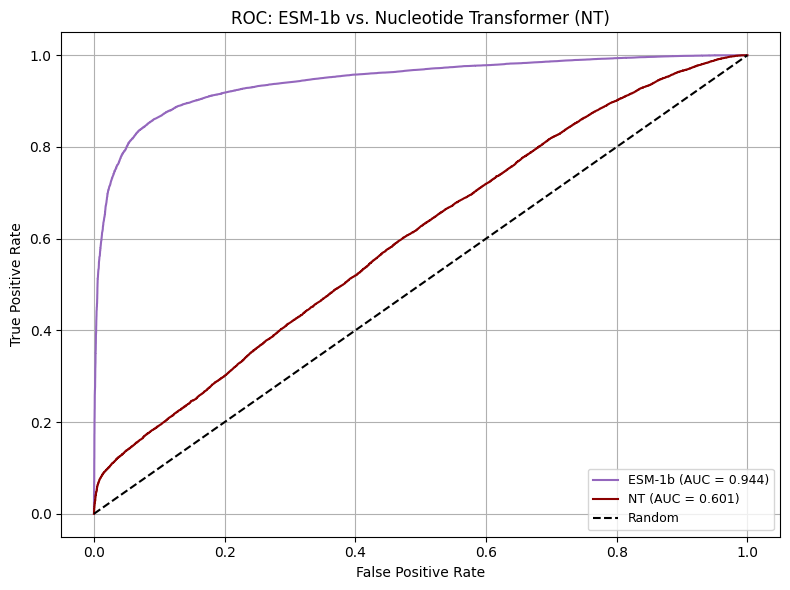

In [ ]:
# Plot 1: ESM vs NT
plot_roc(["ESM-1b", "NT"], title="ROC: ESM-1b vs. Nucleotide Transformer (NT)")

 4. Why do you think the model that performed better, did?

 Answer: **[TO-DO]**


Now, the results above aren't truly a fair comparison. ESM-1b is only reporting it's score on coding variants, whereas NT also has predictions on non-coding pathogenicity. To be fair, we need to also evaluate NT on  only at the protein-coding variants, and compare to ESM-1b.


5. If we only look at protein-coding variant performance, do we expect NT to perform better or worse than it did on all the variants?

Answer: **[TO-DO]**

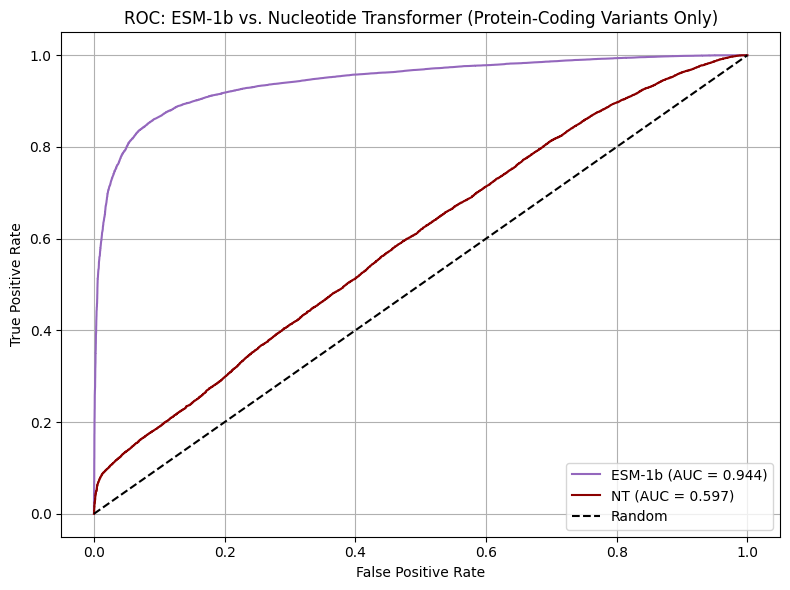

In [ ]:
def plot_roc_protein_only(models, title):
    plt.figure(figsize=(8, 6))

    # Use only variants where ESM-1b is not NaN
    protein_mask = clinvar_df["ESM-1b"].notna()
    subset_df = clinvar_df[protein_mask]

    for model in models:
        scores = -subset_df[model].values
        labels = subset_df["label"].values

        valid = ~np.isnan(scores)
        scores = scores[valid]
        labels = labels[valid]

        fpr, tpr, _ = roc_curve(labels, scores)
        auc_score = roc_auc_score(labels, scores)

        plt.plot(fpr, tpr, label=f"{model} (AUC = {auc_score:.3f})", color=model_colors[model])

    plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the plot
plot_roc_protein_only(["ESM-1b", "NT"], "ROC: ESM-1b vs. Nucleotide Transformer (Protein-Coding Variants Only)")


Now let's inspect HyenaDNA and NT.


6. Which model do you think will perform better? Why?

Answer: **[TO-DO]**


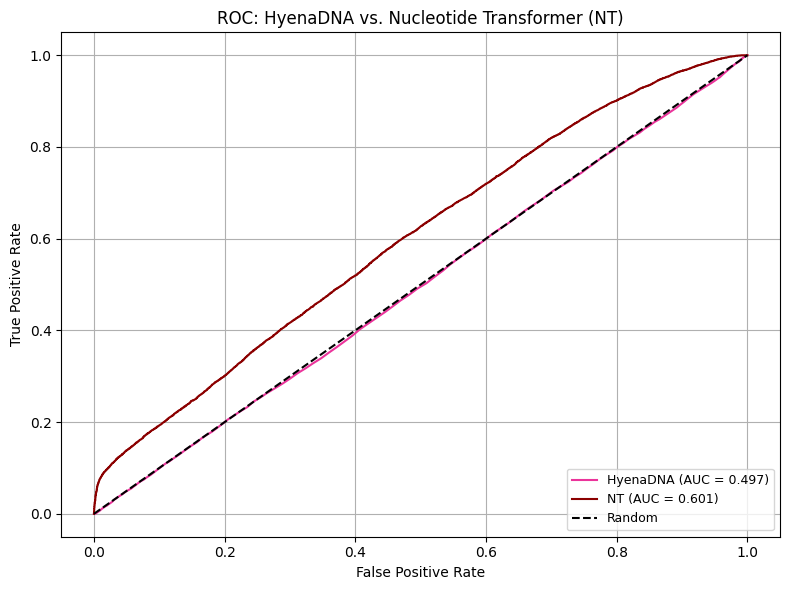

In [ ]:
# Plot 2: HyenaDNA vs NT
plot_roc(["HyenaDNA", "NT"], title="ROC: HyenaDNA vs. Nucleotide Transformer (NT)")


Let's look at all the models in the GPN-MSA paper.

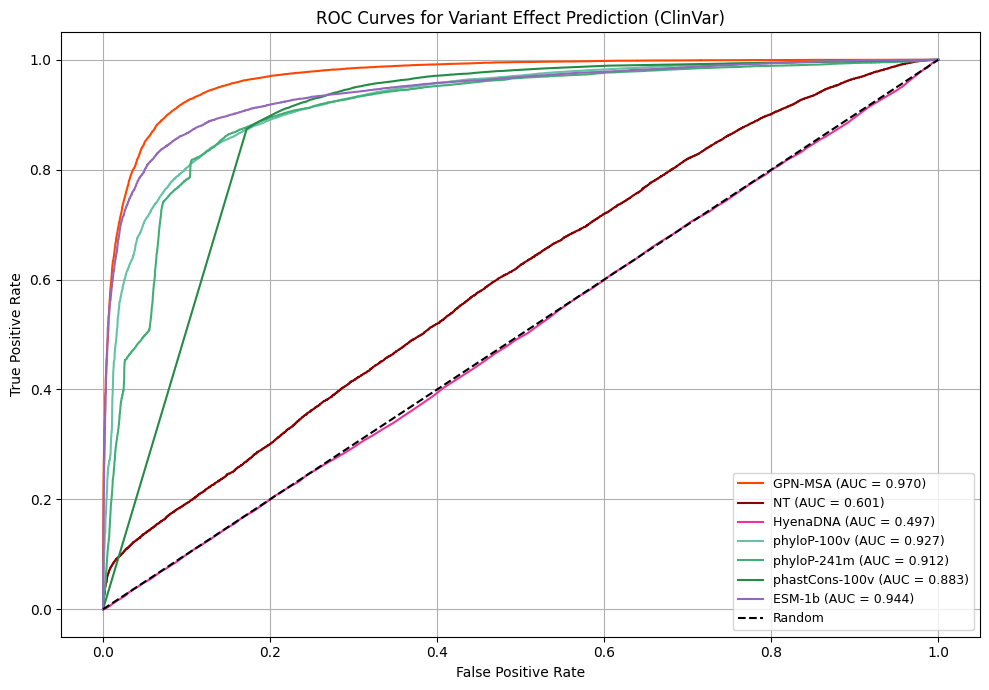

In [ ]:
plt.figure(figsize=(10, 7))

for model in models:
    scores = -clinvar_df[f"{model}"]
    labels = clinvar_df["label"]

    # Drop NaNs
    valid = scores.notna()
    scores = scores[valid]
    labels = labels[valid]

    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)

    plt.plot(fpr, tpr, label=f"{model} (AUC = {auc:.3f})", color=model_colors[model])

# Add random baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Variant Effect Prediction (ClinVar)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


Take a look at the ROC curve for variant effect prediction for all the models and answer the following questions.

7. Which deep learning model performs the best? Why might this be?

Answer: **[TO-DO]**



8. What does it mean that the bioinformatic baselines outperform most of the genome language models?

Answer: **[TO-DO]**


9. What could be the result of the difference in performance between phyloP-100v and phyloP-241m?

Answer: **[TO-DO]**

### Working with Models

Now, let's load the specific models we will be working with. We already saw how these models perform, but how do we *actually evaluate their performance*?


In [ ]:
# Load HyenaDNA:
hyena_model_id = "LongSafari/hyenadna-small-32k-seqlen-hf"
hyena_tokenizer = AutoTokenizer.from_pretrained(hyena_model_id, trust_remote_code=True)
# since HyenaDNA is a causal language model, we load the AutoModelForCausalLM
hyena_model = AutoModelForCausalLM.from_pretrained(hyena_model_id, trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/981 [00:00<?, ?B/s]

configuration_hyena.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LongSafari/hyenadna-small-32k-seqlen-hf:
- configuration_hyena.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/971 [00:00<?, ?B/s]

modeling_hyena.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LongSafari/hyenadna-small-32k-seqlen-hf:
- modeling_hyena.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

HyenaDNA is a causal language model (CLM), meaning it predicts the next token given previous ones (left-to-right). We'll evaluate it using next-token log-likelihood.

In [ ]:
# Load Nucleotide Transformer (nt)
nt_model_id = "InstaDeepAI/nucleotide-transformer-500m-human-ref"
nt_tokenizer = AutoTokenizer.from_pretrained(nt_model_id)
# since nt is a BERT-style masked language model, we load the AutoModelForMaskedLM
nt_model = AutoModelForMaskedLM.from_pretrained(nt_model_id, trust_remote_code=True)

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

EsmForMaskedLM LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NT is a masked language model (MLM), similar to BERT. It predicts masked tokens based on bidirectional context. We'll use this to compare log-likelihoods for the reference vs. variant allele at masked positions.

We’ll now evaluate how both models respond to real variants using sequences from the human genome (hg38.ml.fa).

Let’s begin by:

- Selecting 10 random variants from our clinvar_df

- Extracting 1,000bp windows centered on each variant

- Score both the reference and alternate allele in context

- Take the average score of forward and reverse strand for robustness


10.  Why might a model give different predictions for a sequence and its reverse complement? Hint, think about the architecture of our models.

Answer: **[TO-DO]**




*Answer: HyenaDNA processes left-to-right, and we're centering the variant. NT uses learned 6-mers, and direction matters for tokenization.Reverse complements aren't just flipped, they often have different token boundaries and prediction dynamics.*


Selecting 10 random variants:

In [ ]:
# Ensure chromosome format matches FASTA (e.g., "chr1", "chr17")
clinvar_df["chrom"] = clinvar_df["chrom"].astype(str)
clinvar_df["chrom"] = "chr" + clinvar_df["chrom"]

# Filter for biallelic SNPs and valid chromosomes
valid_variants = clinvar_df[
    (clinvar_df["ref"].str.len() == 1) &
    (clinvar_df["alt"].str.len() == 1) &
    (clinvar_df["chrom"].isin(fasta.keys()))
].copy()

print(f"Valid variants after filtering: {len(valid_variants)}")

# Sample 10
if len(valid_variants) >= 10:
    variant_subset = valid_variants.sample(n=10, random_state=42).reset_index(drop=True)
else:
    raise ValueError("Not enough valid variants to sample 10 examples.")

Valid variants after filtering: 40960


Helpers:

In [ ]:
from pyfaidx import Fasta

def extract_centered_sequence(genome: Fasta, chrom: str, pos_1based: int, flank: int = 500):
    """
    Returns (seq, var_idx) where len(seq) == 2*flank+1 and seq[var_idx] is the REF base.
    pos_1based is VCF-style (1-based inclusive).
    """
    assert pos_1based >= 1, "VCF positions are 1-based"
    chrom_len = len(genome[chrom])

    # clamp to genome bounds
    start_0 = max(0, pos_1based - 1 - flank)
    end_0   = min(chrom_len, pos_1based - 1 + flank + 1)  # half-open

    seq = str(genome[chrom][start_0:end_0]).upper()
    # compute index of the variant within the returned window
    var_idx = (pos_1based - 1) - start_0

    # if we got truncated near edges, pad symmetrically so length stays odd
    need = 2*flank + 1 - len(seq)
    if need > 0:
        left_pad = min(need, start_0)  # how much we *could* have taken on the left
        right_pad = need - left_pad
        seq = ("N"*left_pad) + seq + ("N"*right_pad)
        var_idx += left_pad

    assert len(seq) == 2*flank + 1, f"Got {len(seq)} bp"
    return seq, var_idx


def reverse_complement(seq):
    complement = str.maketrans("ACGT", "TGCA")
    return seq.translate(complement)[::-1]


def average_strand_scores(score_fn, model, tokenizer, sequence, variant_pos_in_seq, ref, alt):
    # Forward strand
    f_ref_score, f_alt_score = score_fn(model, tokenizer, sequence, variant_pos_in_seq, ref, alt)

    # Reverse strand
    rc_sequence = reverse_complement(sequence)
    rc_ref = reverse_complement(ref)
    rc_alt = reverse_complement(alt)
    rc_pos = len(sequence) - variant_pos_in_seq - 1  # flip position

    r_ref_score, r_alt_score = score_fn(model, tokenizer, rc_sequence, rc_pos, rc_ref, rc_alt)

    # Average scores
    return (
        np.mean([f_ref_score, r_ref_score]),
        np.mean([f_alt_score, r_alt_score])
    )



When working with genomic variants, it’s critical to confirm that the reference base in your dataset matches the base in the reference genome. This is especially important before scoring with a language model.

Here’s some buggy code that tries to do this:

In [ ]:
def extract_ref_base(chrom, pos):
    return fasta[chrom][pos].seq.upper()  # 🐛


In [ ]:
row = variant_subset.iloc[4]
chrom = row["chrom"]
pos = int(row["pos"])  # Just in case it's a string

print("REF from data:", row["ref"])
print("REF from genome:", extract_ref_base(chrom, pos))

REF from data: T
REF from genome: A


11. What's wrong with the code? Why doesn't the reference sequence match?

Answer: **[TO-DO]**


Here's some help:
[pyfaidx docs](https://github.com/mdshw5/pyfaidx#using-python-slice-notation)

In [ ]:
#Answer:
def extract_ref_base(chrom, pos):
    # correct line here

Now try again:

In [ ]:
row = variant_subset.iloc[4]
chrom = row["chrom"]
pos = int(row["pos"])  # Just in case it's a string

print("REF from data:", row["ref"])
print("REF from genome:", extract_ref_base(chrom, pos))

REF from data: T
REF from genome: T


Now that we understanding indexing in Python and in variant effect files better, let's set up scoring functions for HyenaDNA and NT.

HyenaDNA:

In [ ]:
def score_hyena(model, tokenizer, sequence, variant_pos_in_seq, ref_base, alt_base, device="cuda"):
    model.eval()
    model.to(device)

    # Tokenize full sequence
    input_ids = tokenizer(sequence, return_tensors="pt")["input_ids"].to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(input_ids).logits  # shape: (1, seq_len, vocab_size)

    # Get position of interest
    target_pos = variant_pos_in_seq  # already 0-indexed

    # Score the next-token prediction (causal model)
    log_probs = torch.log_softmax(logits[0, target_pos - 1], dim=-1)  # Predicting this position

    ref_token = tokenizer(ref_base)["input_ids"][0]
    alt_token = tokenizer(alt_base)["input_ids"][0]

    ref_score = log_probs[ref_token].item()
    alt_score = log_probs[alt_token].item()
    return ref_score, alt_score


NT:

In [ ]:
def score_nt_kmer(model, tokenizer, sequence, variant_pos_in_seq, ref_base, alt_base,
                  device="cuda", k=6):
    """
    Pseudo log-likelihood for NT with arbitrary tokenizer stride.
    Finds token indices whose k-mers cover the variant, masks them, and sums log p(correct token).
    """
    model.eval(); model.to(device)
    assert sequence[variant_pos_in_seq].upper() == ref_base.upper(), "REF mismatch vs sequence"

    # Build ALT sequence
    alt_seq = sequence[:variant_pos_in_seq] + alt_base + sequence[variant_pos_in_seq+1:]

    # Encode (no specials)
    enc_ref = tokenizer(sequence, add_special_tokens=False, return_tensors="pt").to(device)
    enc_alt = tokenizer(alt_seq, add_special_tokens=False, return_tensors="pt").to(device)
    ids_ref = enc_ref["input_ids"].clone()
    ids_alt = enc_alt["input_ids"].clone()
    mask_id = tokenizer.mask_token_id
    if mask_id is None:
        raise ValueError("NT tokenizer needs a mask_token_id")

    # Infer tokenizer stride (1 for overlapping, k for non-overlapping)
    L_bp = len(sequence)
    Ltkn = ids_ref.shape[1]
    if Ltkn == 0:
        return float("nan"), float("nan")
    # tokens expected if stride=1 would be L_bp - k + 1
    stride_est = max(1, round((L_bp - k + 1) / Ltkn))

    # Token start positions present in encoding
    token_starts = [i * stride_est for i in range(Ltkn)]
    # Select token indices whose k-mer covers the variant base
    target_token_idxs = [i for i, s in enumerate(token_starts)
                         if s <= variant_pos_in_seq <= s + k - 1 and s + k <= L_bp]

    if not target_token_idxs:
        # Near edges or tokenizer quirks; skip
        return float("nan"), float("nan")

    # Helper to get single token id for a k-mer
    def kmer_id(s: str) -> int:
        ids = tokenizer(s, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"k-mer didn’t map to one token: {s} -> {ids}")
        return ids[0]

    # Build REF/ALT target token ids per masked index
    ref_target_ids, alt_target_ids = [], []
    for i in target_token_idxs:
        s = token_starts[i]
        ref_target_ids.append(kmer_id(sequence[s:s+k]))
        alt_target_ids.append(kmer_id(alt_seq[s:s+k]))

    @torch.no_grad()
    def pll(input_ids, target_ids):
        total = 0.0
        for idx, tok_i in enumerate(target_token_idxs):
            masked = input_ids.clone()
            masked[0, tok_i] = mask_id
            logits = model(input_ids=masked).logits[0, tok_i]
            total += torch.log_softmax(logits, dim=-1)[target_ids[idx]].item()
        return total

    ref_score = pll(ids_ref, ref_target_ids)
    alt_score = pll(ids_alt, alt_target_ids)
    return ref_score, alt_score


Predict over ten variants:

In [ ]:
for i, row in variant_subset.iterrows():
    chrom = row["chrom"]
    pos = row["pos"]
    ref = row["ref"]
    alt = row["alt"]

    flank = 500  # -> 1001-bp window
    sequence, variant_pos_in_seq = extract_centered_sequence(fasta, chrom, pos, flank=flank)

    # hard check against FASTA
    ref_from_fa = str(fasta[chrom][pos-1:pos]).upper()
    if ref_from_fa != ref.upper():
        print(f"[SKIP] REF mismatch at {chrom}:{pos} FASTA={ref_from_fa} VCF={ref}")
        continue
    if sequence[variant_pos_in_seq] != ref.upper():
        print(f"[SKIP] Window mismatch at {chrom}:{pos}")
        continue
    variant_pos_in_seq = 500  # center of 1000bp window

    # IMPORTANT: check ref base matches
    assert extract_ref_base(chrom, pos) == ref, f"Mismatch at {chrom}:{pos}"

    hyena_ref, hyena_alt = average_strand_scores(
        score_hyena, hyena_model, hyena_tokenizer, sequence, variant_pos_in_seq, ref, alt
    )

    nt_ref, nt_alt = average_strand_scores(
        score_nt_kmer, nt_model, nt_tokenizer, sequence, variant_pos_in_seq, ref, alt
    )

    print(f"\nVariant {i+1}: {chrom}:{pos} {ref}>{alt}")
    print(f"HyenaDNA Δlog-likelihood = {hyena_ref - hyena_alt:.3f}")
    print(f"Nucleotide Transformer Δlog-likelihood = {nt_ref - nt_alt:.3f}")



Variant 1: chr6:112140887 G>A
HyenaDNA Δlog-likelihood = -1.156
Nucleotide Transformer Δlog-likelihood = -2.325

Variant 2: chr12:6016164 T>C
HyenaDNA Δlog-likelihood = 0.370
Nucleotide Transformer Δlog-likelihood = -1.826

Variant 3: chr19:40877894 G>A
HyenaDNA Δlog-likelihood = -1.015
Nucleotide Transformer Δlog-likelihood = 0.201

Variant 4: chr6:31356287 T>A
HyenaDNA Δlog-likelihood = -0.027
Nucleotide Transformer Δlog-likelihood = 1.320

Variant 5: chrX:31875190 T>G
HyenaDNA Δlog-likelihood = 0.060
Nucleotide Transformer Δlog-likelihood = 0.284

Variant 6: chr18:51065532 C>A
HyenaDNA Δlog-likelihood = -0.691
Nucleotide Transformer Δlog-likelihood = -0.311

Variant 7: chr9:130458578 G>A
HyenaDNA Δlog-likelihood = -1.161
Nucleotide Transformer Δlog-likelihood = -0.252

Variant 8: chr12:48202763 C>T
HyenaDNA Δlog-likelihood = -0.099
Nucleotide Transformer Δlog-likelihood = 0.268

Variant 9: chr17:80113001 C>T
HyenaDNA Δlog-likelihood = -1.002
Nucleotide Transformer Δlog-likelihood =

## Post-Module

So far we’ve looked at how models trained on genomic data behave in general by examining their pre-trained performance on predicting the effects of genomic variants.

Now let’s examine another aspect of pre-traine gLM performance:  **cross-entropy (CE) loss** across different types of regions in the genome.

Unlike natural language, the genome is not evenly “informative.”  
Large parts of it are made up of **repeats** (transposons, satellites, etc.), which make up a huge fraction of the human genome. These regions can dominate the training signal, but they don’t carry the same kind of complexity or information density as, say, **exons**, which encode proteins.

When models are trained NLP-style on the *entire* genome, they end up spending a lot of compute memorizing or overfitting to repeats, instead of allocating capacity to more structured, functionally relevant parts like exons. This imbalance in the “noise ratio” is one reason why genomic LMs may struggle to generalize.

Here we directly compare **average CE loss** across:
- **Exons**: protein-coding segments, high functional signal  
- **Repeats**: low-information, highly redundant regions

The exercise:  
1. Compute and compare CE losses for exons vs repeats (done below).  
2. As a follow-up, try **fine-tuning a smaller model** specifically on regions where the baseline loss is higher.  
   - Does the CE loss in those regions improve?  
   - Do we see more efficient use of model capacity?  

This lets you connect the model’s performance back to real genomic structure, and motivates why region-aware training strategies might matter for biology.



### Bed Info

In [ ]:
exon_text="""
chr2	208330523	208330694	ENST00000264380.9	0.0	+
chr2	37060581	37060733	ENST00000233099.6	0.0	-
chr2	9954915	9955101	ENST00000324907.14	0.0	+
chr2	232844369	232844574	ENST00000409547.5	0.0	+
chr2	91714629	91714745	ENST00000445955.1	0.0	-
chr2	79158651	79158769	ENST00000409839.7	0.0	-
chr2	73640832	73641236	ENST00000755937.1	0.0	+
chr2	45546732	45546839	ENST00000263736.5	0.0	-
chr2	231807487	231809253	ENST00000350033.8	0.0	+
chr2	32252419	32252679	ENST00000360906.9	0.0	-
chr2	218661406	218661545	ENST00000392110.6	0.0	+
chr2	232567078	232567214	ENST00000409322.5	0.0	+
chr2	178689290	178689373	ENST00000412264.2	0.0	-
chr2	27640043	27640125	ENST00000407583.7	0.0	+
chr2	196780559	196780662	ENST00000263956.8	0.0	-
chr2	147396231	147396364	ENST00000797339.1	0.0	-
chr2	11130470	11130519	ENST00000737027.1	0.0	+
chr2	10753981	10754066	ENST00000635370.1	0.0	+
chr2	29121374	29121521	ENST00000401605.5	0.0	+
chr2	71598564	71598745	ENST00000410041.1	0.0	+
chr2	74366244	74366375	ENST00000680606.1	0.0	-
chr2	173359255	173359491	ENST00000306721.8	0.0	+
chr2	200688679	200688740	ENST00000491025.6	0.0	+
chr2	10302904	10303177	ENST00000307845.8	0.0	+
chr2	185756192	185756278	ENST00000424728.6	0.0	+
chr2	69182877	69182983	ENST00000362590.2	0.0	+
chr2	229858772	229859574	ENST00000675903.1	0.0	-
chr2	210577421	210577510	ENST00000233072.10	0.0	+
chr2	222887830	222887888	ENST00000357430.8	0.0	+
chr2	178711944	178712222	ENST00000412264.2	0.0	-
chr2	144141882	144142055	ENST00000392871.6	0.0	-
chr2	73000431	73000487	ENST00000272433.7	0.0	-
chr2	157738440	157738570	ENST00000683487.1	0.0	-
chr2	196220039	196220153	ENST00000644978.2	0.0	-
chr2	95121734	95121808	ENST00000272418.7	0.0	-
chr2	1979723	1979777	ENST00000648339.1	0.0	-
chr2	237342065	237342161	ENST00000353578.9	0.0	-
chr2	55209404	55209516	ENST00000401408.6	0.0	-
chr2	221961737	221963765	ENST00000432228.1	0.0	+
chr2	147922973	147923111	ENST00000241416.12	0.0	+
chr2	110323871	110323926	ENST00000636301.2	0.0	+
chr2	95003545	95003843	ENST00000620774.1	0.0	-
chr2	53895007	53895076	ENST00000404125.6	0.0	-
chr2	71611245	71611346	ENST00000394120.6	0.0	+
chr2	238142799	238142931	ENST00000409223.2	0.0	+
chr2	109813460	109813655	ENST00000016946.8	0.0	+
chr2	32197344	32197392	ENST00000406369.2	0.0	+
chr2	28849850	28850610	ENST00000334056.10	0.0	+
chr2	127203372	127203571	ENST00000409327.2	0.0	-
chr2	30447246	30447383	ENST00000379509.8	0.0	+
chr2	113890089	113890323	ENST00000263238.7	0.0	+
chr2	110793650	110793736	ENST00000389811.8	0.0	+
chr2	200859680	200859746	ENST00000321356.9	0.0	-
chr2	86815347	86815718	ENST00000393759.6	0.0	-
chr2	17696289	17696426	ENST00000351948.8	0.0	-
chr2	230925168	230925226	ENST00000622008.4	0.0	-
chr2	160112080	160112199	ENST00000283249.7	0.0	-
chr2	178617779	178618081	ENST00000460472.6	0.0	-
chr2	40174825	40174842	ENST00000417271.2	0.0	-
chr2	127051154	127051243	ENST00000393040.7	0.0	-
chr2	27280166	27280233	ENST00000402462.5	0.0	+
chr2	180555140	180555206	ENST00000799803.1	0.0	+
chr2	96947818	96947902	ENST00000490605.3	0.0	-
chr2	205740519	205740663	ENST00000360409.7	0.0	+
chr2	202186933	202187098	ENST00000498697.3	0.0	+
chr2	116295374	116295439	ENST00000847484.1	0.0	+
chr2	190986854	190986941	ENST00000673777.1	0.0	-
chr2	65253728	65253864	ENST00000260641.10	0.0	+
chr2	224170656	224171849	ENST00000745745.1	0.0	+
chr2	26477416	26477506	ENST00000338581.10	0.0	-
chr2	19351485	19352410	ENST00000272223.3	0.0	-
chr2	215378175	215378262	ENST00000432072.6	0.0	-
chr2	73981109	73981441	ENST00000804860.1	0.0	-
chr2	240698157	240698483	ENST00000337801.9	0.0	+
chr2	96342050	96342140	ENST00000427946.5	0.0	+
chr2	27325849	27326893	ENST00000359541.6	0.0	-
chr2	74361155	74361636	ENST00000680606.1	0.0	-
chr2	32147218	32147258	ENST00000621856.2	0.0	+
chr2	127293513	127293718	ENST00000285398.7	0.0	-
chr2	95025793	95025885	ENST00000353004.7	0.0	+
chr2	159149142	159149272	ENST00000263635.8	0.0	+
chr2	207251710	207251866	ENST00000758487.1	0.0	+
chr2	119366357	119366682	ENST00000409523.1	0.0	-
chr2	55296258	55296523	ENST00000263630.13	0.0	-
chr2	120903614	120903711	ENST00000734153.1	0.0	-
chr2	113242008	113242130	ENST00000429538.8	0.0	-
chr2	71431327	71431428	ENST00000264447.9	0.0	+
chr2	217835091	217835166	ENST00000419504.6	0.0	-
chr2	87206021	87206055	ENST00000797926.1	0.0	-
chr2	222934530	222934687	ENST00000681697.1	0.0	+
chr2	219168195	219168318	ENST00000455516.6	0.0	-
chr2	210519551	210519670	ENST00000673510.1	0.0	+
chr2	26479264	26479384	ENST00000403946.7	0.0	-
chr2	201286459	201286594	ENST00000440732.6	0.0	+
chr2	206786555	206786862	ENST00000765262.1	0.0	-
chr2	60782686	60782770	ENST00000238714.8	0.0	+
chr2	178587118	178587417	ENST00000342992.11	0.0	-
chr2	230817754	230817897	ENST00000409788.7	0.0	+
chr2	79137224	79137342	ENST00000447469.5	0.0	-
chr2	55339464	55339648	ENST00000646796.1	0.0	-
chr2	161977722	161977760	ENST00000415876.6	0.0	+
chr2	127063571	127063646	ENST00000409400.1	0.0	-
chr2	88185898	88186458	ENST00000496844.6	0.0	+
chr2	208300937	208301094	ENST00000407449.5	0.0	+
chr2	219254095	219254608	ENST00000392088.6	0.0	-
chr2	182167887	182168290	ENST00000358139.6	0.0	-
chr2	72498454	72498551	ENST00000272427.11	0.0	-
chr2	219208977	219209049	ENST00000409336.5	0.0	+
chr2	105386361	105386540	ENST00000322142.13	0.0	-
chr2	239630578	239630839	ENST00000446029.1	0.0	+
chr2	240719774	240719926	ENST00000674907.2	0.0	-
chr2	24216049	24216232	ENST00000361999.7	0.0	-
chr2	74265104	74265264	ENST00000451608.2	0.0	-
chr2	11177737	11178856	ENST00000295083.8	0.0	+
chr2	101698473	101698538	ENST00000634702.1	0.0	+
chr2	131646704	131647364	ENST00000605465.1	0.0	-
chr2	87467445	87467960	ENST00000776867.1	0.0	-
chr2	25822297	25822535	ENST00000773213.1	0.0	+
chr2	71590211	71590288	ENST00000409582.7	0.0	+
chr2	188900898	188901045	ENST00000787725.1	0.0	-
chr2	229879982	229880128	ENST00000704578.1	0.0	-
chr2	101855977	101856138	ENST00000350878.9	0.0	+
chr2	71570229	71570334	ENST00000413539.6	0.0	+
chr2	215038943	215039041	ENST00000628464.2	0.0	+
chr2	172497975	172498100	ENST00000409080.6	0.0	+
chr2	130776646	130776957	ENST00000455007.1	0.0	+
chr2	209943380	209943514	ENST00000673920.1	0.0	+
chr2	159969256	159969359	ENST00000392771.1	0.0	-
chr2	47005922	47006059	ENST00000319190.11	0.0	+
chr2	86879469	86879551	ENST00000426186.2	0.0	+
chr2	45392945	45393129	ENST00000263736.5	0.0	-
chr2	80581706	80581819	ENST00000343114.7	0.0	+
chr2	233281105	233281175	ENST00000347464.9	0.0	+
chr2	185799697	185809133	ENST00000424728.6	0.0	+
chr2	178725768	178726046	ENST00000589042.5	0.0	-
chr2	86489520	86489659	ENST00000312912.10	0.0	+
chr2	233460194	233460345	ENST00000409813.7	0.0	+
chr2	191819961	191820251	ENST00000728915.1	0.0	+
chr2	151409883	151410033	ENST00000453091.6	0.0	+
chr2	191678990	191679128	ENST00000674172.1	0.0	+
chr2	131421506	131421614	ENST00000816270.1	0.0	-
chr2	117538509	117539190	ENST00000752864.1	0.0	+
chr2	72133023	72133307	ENST00000546307.5	0.0	-
chr2	44323262	44323411	ENST00000378511.7	0.0	-
chr2	174757566	174757675	ENST00000348749.9	0.0	-
chr2	171117739	171117857	ENST00000431350.7	0.0	-
chr2	28519705	28519763	ENST00000422425.6	0.0	+
chr2	236748369	236748410	ENST00000455068.1	0.0	+
chr2	19969480	19969605	ENST00000345530.8	0.0	-
chr2	36590903	36591011	ENST00000379245.8	0.0	-
chr2	51331501	51332897	ENST00000779423.1	0.0	-
chr2	204965152	204965323	ENST00000349953.7	0.0	+
chr2	55212673	55212806	ENST00000406076.5	0.0	-
chr2	241342992	241343093	ENST00000401990.5	0.0	+
chr2	219038375	219038578	ENST00000341552.10	0.0	-
chr2	147896364	147896508	ENST00000535787.5	0.0	+
chr2	197778975	197779066	ENST00000282278.12	0.0	-
chr2	25342430	25342590	ENST00000406659.3	0.0	-
chr2	127638428	127639428	ENST00000409808.6	0.0	-
chr2	127502815	127502872	ENST00000637187.2	0.0	-
chr2	197523624	197523686	ENST00000323303.9	0.0	+
chr2	164704444	164704518	ENST00000342193.8	0.0	-
chr2	178599146	178599445	ENST00000359218.11	0.0	-
chr2	85316397	85316529	ENST00000501107.2	0.0	+
chr2	181481598	181481683	ENST00000397033.7	0.0	+
chr2	3460263	3460336	ENST00000382110.6	0.0	+
chr2	218990852	218990994	ENST00000392096.6	0.0	-
chr2	229798875	229799049	ENST00000389045.7	0.0	-
chr2	37208875	37212677	ENST00000606229.1	0.0	+
chr2	219038375	219038578	ENST00000410037.5	0.0	-
chr2	178592379	178592660	ENST00000460472.6	0.0	-
chr2	233926533	233926654	ENST00000324695.9	0.0	+
chr2	87179989	87180106	ENST00000454465.2	0.0	+
chr2	240021197	240021412	ENST00000676929.1	0.0	-
chr2	209625053	209625129	ENST00000682079.1	0.0	+
chr2	110283679	110283804	ENST00000633535.1	0.0	+
chr2	37019809	37019877	ENST00000233099.6	0.0	-
chr2	97018343	97018604	ENST00000510981.1	0.0	-
chr2	151596958	151597062	ENST00000397345.8	0.0	-
chr2	54959104	54959261	ENST00000356458.8	0.0	+
chr2	159229578	159232659	ENST00000263635.8	0.0	+
chr2	949641	949788	ENST00000758542.1	0.0	-
chr2	229791124	229791251	ENST00000704585.1	0.0	-
chr2	229778433	229778587	ENST00000704581.1	0.0	-
chr2	86563304	86563479	ENST00000409225.2	0.0	-
chr2	172301145	172301216	ENST00000657632.1	0.0	+
chr2	237911528	237911956	ENST00000409726.5	0.0	+
chr2	61499713	61499894	ENST00000678182.1	0.0	-
chr2	174472965	174473364	ENST00000392551.6	0.0	-
chr2	33252677	33252844	ENST00000407925.5	0.0	+
chr2	203380208	203380384	ENST00000424558.5	0.0	+
chr2	97541911	97541983	ENST00000359901.9	0.0	-
chr2	208245319	208245424	ENST00000415913.5	0.0	-
chr2	174481497	174481987	ENST00000392551.6	0.0	-
chr2	201284816	201285317	ENST00000696067.1	0.0	+
chr2	69303549	69303650	ENST00000786264.1	0.0	-
chr2	241689838	241690653	ENST00000636051.1	0.0	+
chr2	122104634	122105367	ENST00000796774.1	0.0	-
chr2	237994744	237994809	ENST00000272930.9	0.0	+
chr2	55312434	55312579	ENST00000336838.10	0.0	-
chr2	178711944	178712222	ENST00000589042.5	0.0	-
chr2	240761229	240761377	ENST00000320389.12	0.0	-
chr2	178794399	178794551	ENST00000342992.11	0.0	-
chr2	233101	233229	ENST00000356150.10	0.0	-
chr2	199948318	199948472	ENST00000354611.9	0.0	-
chr2	105345315	105349211	ENST00000258457.7	0.0	+
chr2	169603642	169603694	ENST00000448752.7	0.0	+
chr2	8800400	8800498	ENST00000256707.8	0.0	-
chr2	37148857	37149023	ENST00000233057.9	0.0	-
chr2	118032172	118032359	ENST00000627670.3	0.0	+
chr2	99364271	99364421	ENST00000289371.11	0.0	+
chr2	74620695	74620979	ENST00000428904.1	0.0	-
chr2	24728308	24728476	ENST00000406961.5	0.0	+
chr2	74894244	74894355	ENST00000840200.1	0.0	+
chr2	188990096	188990149	ENST00000304636.9	0.0	+
chr2	27276726	27276841	ENST00000402462.5	0.0	+
chr2	27583046	27583142	ENST00000505973.1	0.0	+
chr2	231331793	231331897	ENST00000349938.8	0.0	+
chr2	169191832	169192033	ENST00000649046.1	0.0	-
chr2	26383299	26383347	ENST00000260585.12	0.0	+
chr2	237720772	237720822	ENST00000308482.14	0.0	+
chr2	178651243	178651320	ENST00000342992.11	0.0	-
chr2	238349325	238349408	ENST00000373327.5	0.0	+
chr2	40174706	40174720	ENST00000403092.5	0.0	-
chr2	42288227	42288322	ENST00000318522.10	0.0	+
chr2	215388212	215388301	ENST00000446046.5	0.0	-
chr2	166051719	166051988	ENST00000641575.1	0.0	-
chr2	178578790	178580906	ENST00000603521.1	0.0	+
chr2	55660157	55660193	ENST00000447944.7	0.0	-
chr2	86907829	86908016	ENST00000426186.2	0.0	+
chr2	178777704	178777975	ENST00000359218.11	0.0	-
chr2	201135972	201136107	ENST00000341222.10	0.0	+
chr2	148020633	148020747	ENST00000535373.5	0.0	-
chr2	71574198	71574371	ENST00000409762.5	0.0	+
chr2	178714292	178714573	ENST00000589042.5	0.0	-
chr2	236344557	236344643	ENST00000409907.8	0.0	-
chr2	230986984	230987377	ENST00000793625.1	0.0	-
chr2	219387070	219387163	ENST00000523282.6	0.0	-
chr2	69854823	69854960	ENST00000282570.4	0.0	+
chr2	227554436	227554545	ENST00000409171.5	0.0	+
chr2	100904733	100904786	ENST00000335681.10	0.0	+
chr2	131369062	131369711	ENST00000424905.1	0.0	-
chr2	218264129	218264608	ENST00000248450.9	0.0	-
chr2	242035523	242035629	ENST00000770798.1	0.0	-
chr2	121728477	121728536	ENST00000285814.9	0.0	-
chr2	151552672	151552776	ENST00000427231.7	0.0	-
chr2	177232392	177232583	ENST00000448782.6	0.0	-
chr2	157737316	157737665	ENST00000410057.6	0.0	-
chr2	38954373	38954456	ENST00000398800.8	0.0	+
chr2	82326549	82326762	ENST00000742366.1	0.0	+
chr2	73845167	73845262	ENST00000682847.1	0.0	+
chr2	25377243	25377553	ENST00000406818.8	0.0	-
chr2	110025403	110025573	ENST00000637413.2	0.0	-
chr2	8837780	8838120	ENST00000843866.1	0.0	-
chr2	196156439	196156651	ENST00000409228.5	0.0	-
chr2	181544700	181544796	ENST00000409440.7	0.0	-
chr2	74250343	74250517	ENST00000346834.8	0.0	-
chr2	196592464	196592684	ENST00000260983.8	0.0	-
chr2	72888314	72888604	ENST00000234454.6	0.0	+
chr2	2172872	2172988	ENST00000648318.1	0.0	-
chr2	26465672	26465842	ENST00000272371.7	0.0	-
chr2	224814320	224814364	ENST00000645028.1	0.0	-
chr2	206144892	206145026	ENST00000440274.5	0.0	-
chr2	24693252	24693347	ENST00000395856.3	0.0	+
chr2	74342458	74342537	ENST00000451608.2	0.0	-
chr2	26244748	26244990	ENST00000537713.5	0.0	+
chr2	10848073	10848270	ENST00000744007.1	0.0	-
chr2	108300900	108300935	ENST00000326853.9	0.0	+
chr2	26473132	26473294	ENST00000272371.7	0.0	-
chr2	176531590	176531683	ENST00000815579.1	0.0	-
chr2	74532820	74533350	ENST00000696727.1	0.0	+
chr2	95101677	95101723	ENST00000695433.1	0.0	-
chr2	217907210	217907251	ENST00000682258.1	0.0	-
chr2	169280350	169280519	ENST00000649046.1	0.0	-
chr2	71561752	71561944	ENST00000410020.8	0.0	+
chr2	178717523	178717810	ENST00000589042.5	0.0	-
chr2	43344122	43344237	ENST00000405006.8	0.0	-
chr2	230211470	230211553	ENST00000698099.1	0.0	-
chr2	189733107	189733229	ENST00000313581.4	0.0	+
chr2	190987039	190987068	ENST00000698142.1	0.0	-
chr2	165494759	165494928	ENST00000651982.1	0.0	+
chr2	76514657	76514942	ENST00000719311.1	0.0	+
chr2	240745427	240745517	ENST00000648129.1	0.0	-
chr2	165720597	165720984	ENST00000715193.1	0.0	+
chr2	135390802	135390820	ENST00000401392.5	0.0	-
chr2	64591885	64592665	ENST00000695867.1	0.0	+
chr2	29160333	29160467	ENST00000320081.10	0.0	+
chr2	30688980	30689377	ENST00000789261.1	0.0	+
chr2	215399257	215399351	ENST00000359671.5	0.0	-
chr2	151469711	151469864	ENST00000430328.6	0.0	+
chr2	113193048	113193128	ENST00000245796.11	0.0	+
chr2	147972739	147972829	ENST00000264169.6	0.0	-
chr2	135846237	135846392	ENST00000264156.3	0.0	-
chr2	164213539	164214414	ENST00000445305.1	0.0	+
chr2	230793213	230793331	ENST00000409788.7	0.0	+
chr2	24053902	24053949	ENST00000452109.1	0.0	+
chr2	218394632	218394785	ENST00000233202.11	0.0	+
chr2	214792297	214792445	ENST00000617164.5	0.0	-
chr2	210024033	210024201	ENST00000281772.14	0.0	-
chr2	31187758	31187814	ENST00000403897.4	0.0	-
chr2	24967211	24967293	ENST00000534855.5	0.0	-
chr2	132645101	132646582	ENST00000329321.4	0.0	+
chr2	230442937	230443099	ENST00000409897.5	0.0	+
chr2	110163048	110163132	ENST00000676053.1	0.0	-
chr2	36442615	36442735	ENST00000280527.7	0.0	+
chr2	83879247	83879498	ENST00000840665.1	0.0	+
chr2	65074282	65074404	ENST00000704388.1	0.0	+
chr2	64579486	64579546	ENST00000695866.1	0.0	+
chr2	178616479	178616630	ENST00000460472.6	0.0	-
chr2	157628572	157628727	ENST00000335450.7	0.0	-
chr2	46256860	46257177	ENST00000446949.1	0.0	-
chr2	147150707	147150888	ENST00000662284.1	0.0	+
chr2	62222212	62224731	ENST00000301998.5	0.0	+
chr2	95085391	95087581	ENST00000695433.1	0.0	-
chr2	161965051	161965173	ENST00000446997.6	0.0	+
chr2	84697575	84697727	ENST00000389394.8	0.0	+
chr2	27099196	27099284	ENST00000260599.11	0.0	+
chr2	152694542	152694622	ENST00000545856.8	0.0	-
chr2	179047284	179047406	ENST00000409284.1	0.0	-
chr2	31129277	31129624	ENST00000406653.5	0.0	-
chr2	20917208	20917337	ENST00000796578.1	0.0	+
chr2	213049713	213049880	ENST00000374319.8	0.0	-
chr2	178662729	178662812	ENST00000589042.5	0.0	-
chr2	4656166	4656498	ENST00000412134.6	0.0	-
chr2	28999181	28999468	ENST00000379558.5	0.0	+
chr2	235750354	235750488	ENST00000409457.5	0.0	+
chr2	74475612	74475726	ENST00000393965.8	0.0	-
chr2	56177225	56177364	ENST00000606639.1	0.0	+
chr2	135126181	135126249	ENST00000264158.13	0.0	+
chr2	169240988	169241365	ENST00000649046.1	0.0	-
chr2	168129541	168129606	ENST00000355999.5	0.0	-
chr2	71665162	71665304	ENST00000429174.6	0.0	+
chr2	131611133	131611177	ENST00000397487.4	0.0	+
chr2	24728308	24728476	ENST00000288599.9	0.0	+
chr2	55615451	55615506	ENST00000616288.4	0.0	-
chr2	127059011	127059155	ENST00000316724.10	0.0	-
chr2	552484	552896	ENST00000788942.1	0.0	-
chr2	130008940	130009006	ENST00000416089.1	0.0	+
chr2	86969228	86969315	ENST00000398193.8	0.0	+
chr2	240721807	240721884	ENST00000649306.1	0.0	-
chr2	240890005	240890158	ENST00000402775.6	0.0	-
chr2	159386353	159386607	ENST00000392783.7	0.0	-
chr2	95859861	95860074	ENST00000295246.7	0.0	-
chr2	147955347	147955395	ENST00000540442.5	0.0	-
chr2	220069163	220069296	ENST00000830324.1	0.0	+
chr2	231070025	231070168	ENST00000677230.1	0.0	+
chr2	240719774	240719926	ENST00000647885.1	0.0	-
chr2	182063731	182063791	ENST00000409137.7	0.0	+
chr2	215384860	215384976	ENST00000354785.11	0.0	-
chr2	229778876	229778990	ENST00000704578.1	0.0	-
chr2	169504481	169506655	ENST00000295240.8	0.0	+
chr2	53801397	53801620	ENST00000378239.5	0.0	+
chr2	64572946	64573068	ENST00000409933.6	0.0	+
chr2	97158588	97158655	ENST00000461153.7	0.0	+
chr2	71570229	71570334	ENST00000409744.5	0.0	+
chr2	24665749	24665915	ENST00000288599.9	0.0	+
chr2	190986854	190986947	ENST00000392323.6	0.0	-
chr2	231732433	231733033	ENST00000287600.9	0.0	-
chr2	178604708	178604898	ENST00000589042.5	0.0	-
chr2	25042076	25042319	ENST00000403714.8	0.0	+
chr2	233499879	233499915	ENST00000678225.2	0.0	-
chr2	101466777	101466900	ENST00000428343.6	0.0	-
chr2	24273614	24273741	ENST00000515996.1	0.0	-
chr2	20701570	20701652	ENST00000541941.5	0.0	-
chr2	191678990	191679128	ENST00000674414.1	0.0	+
chr2	166013744	166013898	ENST00000637988.1	0.0	-
chr2	172922281	172922300	ENST00000538974.5	0.0	+
chr2	178730505	178730792	ENST00000342992.11	0.0	-
chr2	54535040	54535138	ENST00000433475.1	0.0	-
chr2	24295664	24295804	ENST00000406921.7	0.0	-
chr2	174445081	174445176	ENST00000392551.6	0.0	-
chr2	27336292	27336470	ENST00000590383.4	0.0	+
chr2	63054047	63054198	ENST00000282549.7	0.0	+
chr2	26346121	26346817	ENST00000447444.5	0.0	-
chr2	197488317	197488491	ENST00000452200.6	0.0	-
chr2	26278614	26278801	ENST00000545822.2	0.0	+
chr2	218582971	218583086	ENST00000273064.11	0.0	+
chr2	74428268	74428396	ENST00000272430.10	0.0	-
chr2	134028435	134028577	ENST00000746265.1	0.0	-
chr2	38748056	38748157	ENST00000409276.5	0.0	-
chr2	189572846	189572961	ENST00000261024.7	0.0	-
chr2	80544982	80545074	ENST00000629316.2	0.0	+
chr2	190978856	190979001	ENST00000673841.1	0.0	-
chr2	197499142	197499438	ENST00000418022.2	0.0	-
chr2	15606150	15606264	ENST00000677302.1	0.0	+
chr2	202300234	202300367	ENST00000264279.10	0.0	+
chr2	27441127	27441180	ENST00000233557.7	0.0	+
chr2	143957195	143957339	ENST00000344850.8	0.0	-
chr2	215430715	215430852	ENST00000336916.8	0.0	-
chr2	191683729	191683804	ENST00000674187.1	0.0	+
chr2	188165754	188165908	ENST00000434418.2	0.0	-
chr2	178436145	178436319	ENST00000325748.9	0.0	-
chr2	101698081	101698137	ENST00000347699.8	0.0	+
chr2	86151297	86151520	ENST00000410111.8	0.0	-
chr2	70418950	70419000	ENST00000452525.1	0.0	+
chr2	217821740	217821938	ENST00000615025.6	0.0	-
chr2	229810880	229811045	ENST00000675903.1	0.0	-
chr2	101858996	101859082	ENST00000324219.9	0.0	+
chr2	74554720	74554814	ENST00000233668.10	0.0	+
chr2	86974681	86974804	ENST00000641458.2	0.0	+
chr2	130913986	130917498	ENST00000409359.7	0.0	+
chr2	43020771	43020985	ENST00000731665.1	0.0	+
chr2	241497616	241497687	ENST00000403346.7	0.0	-
chr2	210017473	210017559	ENST00000429921.5	0.0	+
chr2	97724016	97724438	ENST00000264972.10	0.0	+
chr2	159852201	159852340	ENST00000504764.5	0.0	-
chr2	101867212	101867309	ENST00000625522.3	0.0	+
chr2	234246010	234246164	ENST00000760713.1	0.0	-
chr2	26924887	26925045	ENST00000288699.11	0.0	+
chr2	1886539	1886607	ENST00000428368.7	0.0	-
chr2	159987156	159987358	ENST00000283243.13	0.0	-
chr2	202899531	202899637	ENST00000688520.1	0.0	-
chr2	186622339	186622430	ENST00000433736.6	0.0	+
chr2	31943302	31943383	ENST00000426310.6	0.0	-
chr2	27022212	27022339	ENST00000405074.7	0.0	+
chr2	178544201	178544506	ENST00000460472.6	0.0	-
chr2	71516180	71516242	ENST00000429174.6	0.0	+
chr2	173954873	173956232	ENST00000310015.12	0.0	-
chr2	241463335	241463468	ENST00000264042.8	0.0	+
chr2	43592317	43592420	ENST00000402360.6	0.0	-
chr2	112422548	112422659	ENST00000302558.8	0.0	-
chr2	26314414	26314623	ENST00000421160.6	0.0	-
chr2	79025686	79025773	ENST00000393897.6	0.0	+
chr2	120577043	120577319	ENST00000825040.1	0.0	+
chr2	95893696	95893724	ENST00000295246.7	0.0	-
chr2	54829342	54829477	ENST00000356458.8	0.0	+
chr2	151547429	151547533	ENST00000427231.7	0.0	-
chr2	178542662	178542949	ENST00000589042.5	0.0	-
chr2	223777691	223777869	ENST00000650969.1	0.0	-
chr2	98533377	98533495	ENST00000409851.8	0.0	+
chr2	201480008	201480846	ENST00000392249.6	0.0	+
chr2	215045837	215046015	ENST00000272895.12	0.0	-
chr2	178607021	178607314	ENST00000359218.11	0.0	-
chr2	1840760	1840843	ENST00000649207.1	0.0	-
chr2	217064916	217065014	ENST00000802626.1	0.0	-
chr2	181677506	181678871	ENST00000683430.1	0.0	-
chr2	97618638	97619048	ENST00000650675.1	0.0	+
chr2	215895223	215895455	ENST00000767126.1	0.0	-
chr2	32501713	32501888	ENST00000421745.7	0.0	+
chr2	43844507	43844608	ENST00000272286.4	0.0	+
chr2	86846684	86846773	ENST00000393759.6	0.0	-
chr2	37324904	37325522	ENST00000433893.2	0.0	+
chr2	33520553	33520684	ENST00000402538.8	0.0	+
chr2	232844369	232844574	ENST00000409196.7	0.0	+
chr2	241655271	241655343	ENST00000404914.8	0.0	+
chr2	53896804	53896885	ENST00000404125.6	0.0	-
chr2	89172343	89172553	ENST00000518729.1	0.0	-
chr2	95374296	95374420	ENST00000295225.10	0.0	+
chr2	200897076	200897214	ENST00000409357.5	0.0	+
chr2	71516180	71516242	ENST00000409582.7	0.0	+
chr2	229797690	229797831	ENST00000704577.1	0.0	-
chr2	110658410	110658520	ENST00000302759.11	0.0	-
chr2	70275514	70275666	ENST00000433351.7	0.0	+
chr2	219240191	219240285	ENST00000392089.6	0.0	-
chr2	206756898	206757040	ENST00000454776.6	0.0	-
chr2	86789640	86789750	ENST00000283635.8	0.0	-
chr2	173365452	173365592	ENST00000306721.8	0.0	+
chr2	169631766	169631933	ENST00000678499.1	0.0	+
chr2	85134016	85134079	ENST00000282111.4	0.0	+
chr2	21032354	21032581	ENST00000233242.5	0.0	-
chr2	28752038	28752176	ENST00000296122.10	0.0	+
chr2	206749020	206749183	ENST00000454776.6	0.0	-
chr2	241465460	241466030	ENST00000373287.8	0.0	+
chr2	94792313	94792358	ENST00000700701.1	0.0	-
chr2	17768738	17768811	ENST00000317402.11	0.0	+
chr2	1160147	1160424	ENST00000428335.1	0.0	-
chr2	108746711	108746798	ENST00000283195.11	0.0	+
chr2	240557881	240557988	ENST00000401804.6	0.0	-
chr2	43024107	43024172	ENST00000705222.1	0.0	-
chr2	207678542	207679122	ENST00000691648.2	0.0	+
chr2	86338250	86338512	ENST00000771860.1	0.0	+
chr2	55308809	55309023	ENST00000336838.10	0.0	-
chr2	232747615	232747744	ENST00000409547.5	0.0	+
chr2	152148225	152148300	ENST00000263904.5	0.0	-
chr2	179988577	179988644	ENST00000410053.8	0.0	-
chr2	224703764	224703887	ENST00000638102.1	0.0	-
chr2	150977401	150977446	ENST00000812494.1	0.0	-
chr2	185502663	185502739	ENST00000799165.1	0.0	+
chr2	1892037	1892287	ENST00000648316.1	0.0	-
chr2	241496398	241496534	ENST00000405585.5	0.0	-
chr2	27097503	27097649	ENST00000260598.10	0.0	+
chr2	219473728	219473903	ENST00000312358.12	0.0	+
chr2	48694224	48694304	ENST00000602369.3	0.0	-
chr2	178681079	178681171	ENST00000412264.2	0.0	-
chr2	11767763	11767858	ENST00000674199.1	0.0	+
chr2	120327850	120328227	ENST00000725912.1	0.0	+
chr2	191414048	191414180	ENST00000304164.8	0.0	+
chr2	181057693	181057825	ENST00000410062.9	0.0	+
chr2	48471279	48471367	ENST00000449090.6	0.0	+
chr2	151446426	151446575	ENST00000444746.7	0.0	+
chr2	41947495	41947571	ENST00000649862.1	0.0	-
chr2	16588050	16588129	ENST00000406434.5	0.0	-
chr2	99434332	99434448	ENST00000258428.8	0.0	-
chr2	119340159	119340361	ENST00000409466.6	0.0	-
chr2	15628638	15628710	ENST00000677302.1	0.0	+
chr2	113643190	113643391	ENST00000393166.7	0.0	+
chr2	71570229	71570334	ENST00000258104.8	0.0	+
chr2	219157472	219157684	ENST00000698202.1	0.0	-
chr2	84624902	84625063	ENST00000389394.8	0.0	+
chr2	216610342	216610959	ENST00000457237.1	0.0	-
chr2	32290483	32290636	ENST00000238831.9	0.0	+
chr2	113131045	113131157	ENST00000361779.7	0.0	+
chr2	240761229	240761377	ENST00000648680.1	0.0	-
chr2	183158283	183158411	ENST00000409798.5	0.0	+
chr2	135120819	135120918	ENST00000264158.13	0.0	+
chr2	202817418	202817543	ENST00000392237.6	0.0	-
chr2	233729042	233729993	ENST00000482026.6	0.0	+
chr2	53797515	53797592	ENST00000405123.7	0.0	+
chr2	74483322	74483410	ENST00000233623.11	0.0	+
chr2	55318843	55319004	ENST00000263630.13	0.0	-
chr2	61522611	61522683	ENST00000677813.1	0.0	-
chr2	137563221	137563354	ENST00000409968.6	0.0	+
chr2	9868276	9868429	ENST00000263663.10	0.0	+
chr2	61538138	61538298	ENST00000678790.1	0.0	-
chr2	231798859	231798964	ENST00000373608.7	0.0	+
chr2	108680695	108680770	ENST00000695519.1	0.0	+
chr2	240746039	240746177	ENST00000650053.1	0.0	-
chr2	136126766	136127450	ENST00000805101.1	0.0	+
chr2	217920195	217920236	ENST00000419504.6	0.0	-
chr2	231523187	231525425	ENST00000305141.5	0.0	-
chr2	83072134	83072243	ENST00000784855.1	0.0	-
chr2	87177148	87177234	ENST00000454465.2	0.0	+
chr2	55028164	55028220	ENST00000394611.6	0.0	-
chr2	241126196	241127451	ENST00000544142.5	0.0	-
chr2	222933166	222933280	ENST00000679514.1	0.0	+
chr2	33944428	33944553	ENST00000366209.6	0.0	+
chr2	127623202	127623375	ENST00000409816.8	0.0	+
chr2	15573769	15573868	ENST00000438178.2	0.0	+
chr2	165370126	165370299	ENST00000375437.7	0.0	+
chr2	73260740	73260858	ENST00000520530.3	0.0	-
chr2	69319780	69326233	ENST00000361060.5	0.0	-
chr2	160286969	160287084	ENST00000348849.8	0.0	-
chr2	112551775	112551998	ENST00000537335.5	0.0	+
chr2	99154693	99154942	ENST00000393483.8	0.0	-
chr2	73901276	73901437	ENST00000409624.1	0.0	+
chr2	73534824	73534949	ENST00000613296.6	0.0	+
chr2	9474537	9474647	ENST00000470914.5	0.0	+
chr2	215364879	215364985	ENST00000446046.5	0.0	-
chr2	65589566	65589819	ENST00000420724.1	0.0	-
chr2	131239278	131239444	ENST00000356920.9	0.0	+
chr2	106958696	106959109	ENST00000839218.1	0.0	+
chr2	95109916	95110041	ENST00000695434.1	0.0	-
chr2	26448691	26448803	ENST00000288710.7	0.0	+
chr2	240769133	240769208	ENST00000649096.1	0.0	-
chr2	95100837	95100894	ENST00000695456.1	0.0	-
chr2	112658825	112659094	ENST00000272542.8	0.0	+
chr2	209692625	209696350	ENST00000360351.8	0.0	+
chr2	174587473	174587726	ENST00000454203.1	0.0	+
chr2	131497210	131497293	ENST00000415574.6	0.0	+
chr2	218823646	218823878	ENST00000439262.7	0.0	-
chr2	178618189	178618491	ENST00000460472.6	0.0	-
chr2	108475535	108475635	ENST00000309863.11	0.0	+
chr2	10442012	10442174	ENST00000699836.1	0.0	-
chr2	37260223	37260384	ENST00000234179.8	0.0	-
chr2	86213993	86217110	ENST00000538924.7	0.0	-
chr2	61537562	61537743	ENST00000678182.1	0.0	-
chr2	191148076	191148204	ENST00000450994.2	0.0	-
chr2	86951296	86951360	ENST00000641458.2	0.0	+
chr2	15383215	15383317	ENST00000281513.10	0.0	-
chr2	34138976	34139048	ENST00000649638.1	0.0	-
chr2	197777059	197777113	ENST00000321801.11	0.0	-
chr2	151612186	151612389	ENST00000397345.8	0.0	-
chr2	111265272	111265463	ENST00000728228.1	0.0	+
chr2	230570640	230570715	ENST00000455357.5	0.0	-
chr2	241071796	241071878	ENST00000310397.13	0.0	+
chr2	101414854	101414912	ENST00000428343.6	0.0	-
chr2	151697148	151697252	ENST00000427231.7	0.0	-
chr2	201114944	201115034	ENST00000832402.1	0.0	-
chr2	175074505	175074835	ENST00000392544.5	0.0	-
chr2	37489461	37489581	ENST00000751609.1	0.0	+
chr2	127638721	127639428	ENST00000545738.6	0.0	-
chr2	190987039	190987068	ENST00000361099.8	0.0	-
chr2	64585422	64585545	ENST00000695865.1	0.0	+
chr2	85558440	85558605	ENST00000430215.7	0.0	-
chr2	17774271	17774401	ENST00000381254.7	0.0	+
chr2	226216515	226216722	ENST00000748757.1	0.0	-
chr2	151493353	151493445	ENST00000397345.8	0.0	-
chr2	308939	309424	ENST00000619113.1	0.0	+
chr2	177680826	177680903	ENST00000389683.7	0.0	-
chr2	178770412	178770675	ENST00000589042.5	0.0	-
chr2	219234133	219234288	ENST00000410034.7	0.0	+
chr2	229803571	229803689	ENST00000704581.1	0.0	-
chr2	232832857	232833093	ENST00000373563.9	0.0	+
chr2	232087487	232087721	ENST00000409401.7	0.0	+
chr2	218070500	218070651	ENST00000697321.1	0.0	+
chr2	68819123	68819319	ENST00000467265.5	0.0	+
chr2	119230620	119231034	ENST00000393110.7	0.0	+
chr2	151697544	151697648	ENST00000409198.5	0.0	-
chr2	26457203	26458220	ENST00000338581.10	0.0	-
chr2	216113016	216113129	ENST00000392133.7	0.0	+
chr2	108258966	108259146	ENST00000681802.2	0.0	+
chr2	203217253	203225194	ENST00000683969.1	0.0	+
chr2	101565142	101565298	ENST00000795002.1	0.0	-
chr2	241337673	241337790	ENST00000360051.7	0.0	+
chr2	40175261	40175281	ENST00000332839.9	0.0	-
chr2	229768616	229768719	ENST00000704581.1	0.0	-
chr2	97737473	97737665	ENST00000698508.2	0.0	+
chr2	174422885	174423047	ENST00000409673.7	0.0	+
chr2	100104402	100104518	ENST00000317233.8	0.0	-
chr2	216598628	216598807	ENST00000793139.1	0.0	+
chr2	135721924	135722006	ENST00000683871.1	0.0	+
chr2	106158058	106158118	ENST00000409501.7	0.0	-
chr2	132309309	132309323	ENST00000438300.1	0.0	+
chr2	221572158	221572283	ENST00000409854.5	0.0	-
chr2	97179861	97179933	ENST00000652721.1	0.0	+
chr2	181548545	181548604	ENST00000374970.6	0.0	-
chr2	41871271	41871388	ENST00000411313.1	0.0	+
chr2	65083639	65087004	ENST00000260569.4	0.0	+
chr2	144494265	144496878	ENST00000623674.1	0.0	-
chr2	216245352	216246041	ENST00000787976.1	0.0	+
chr2	127070762	127070816	ENST00000352848.8	0.0	-
chr2	218663892	218664535	ENST00000295704.7	0.0	-
chr2	233475526	233477503	ENST00000678225.2	0.0	-
chr2	61162842	61162955	ENST00000462959.2	0.0	+
chr2	201705416	201705461	ENST00000679516.1	0.0	-
chr2	189258935	189259096	ENST00000747641.1	0.0	-
chr2	97772297	97772424	ENST00000186436.10	0.0	-
chr2	134991537	134991580	ENST00000375844.7	0.0	-
chr2	178598506	178598654	ENST00000412264.2	0.0	-
chr2	247538	247602	ENST00000403712.6	0.0	-
chr2	98610775	98610895	ENST00000409347.5	0.0	+
chr2	96035914	96035974	ENST00000687910.1	0.0	-
chr2	71601499	71601528	ENST00000258104.8	0.0	+
chr2	151461138	151461289	ENST00000444746.7	0.0	+
chr2	240988739	240988870	ENST00000690015.1	0.0	+
chr2	191058202	191058219	ENST00000358470.8	0.0	-
chr2	201133029	201133134	ENST00000341582.10	0.0	+
chr2	215026820	215026938	ENST00000389661.4	0.0	-
chr2	104504868	104505188	ENST00000430551.2	0.0	-
chr2	162194701	162194748	ENST00000443424.5	0.0	-
chr2	152101907	152101964	ENST00000762105.1	0.0	+
chr2	152189985	152190123	ENST00000804695.1	0.0	-
chr2	218634458	218634630	ENST00000450993.7	0.0	+
chr2	71658878	71659033	ENST00000429174.6	0.0	+
chr2	175080660	175080765	ENST00000409635.5	0.0	-
chr2	165845953	165846201	ENST00000715282.1	0.0	-
chr2	231796106	231796308	ENST00000611614.4	0.0	+
chr2	58620169	58620321	ENST00000821970.1	0.0	-
chr2	215419242	215419385	ENST00000359671.5	0.0	-
chr2	27566735	27582722	ENST00000447166.3	0.0	+
chr2	95793731	95793835	ENST00000444924.1	0.0	+
chr2	177215539	177215661	ENST00000676629.1	0.0	+
chr2	215942584	215944997	ENST00000263268.11	0.0	-
chr2	206570740	206570811	ENST00000264377.8	0.0	+
chr2	202284345	202284481	ENST00000264279.10	0.0	+
chr2	109564366	109564534	ENST00000356688.8	0.0	-
chr2	29023086	29023191	ENST00000379558.5	0.0	+
chr2	233981774	233981915	ENST00000324695.9	0.0	+
chr2	74424875	74424975	ENST00000409791.5	0.0	+
chr2	218312832	218312869	ENST00000834158.1	0.0	-
chr2	100271875	100284492	ENST00000393437.8	0.0	-
chr2	73828918	73828996	ENST00000682847.1	0.0	+
chr2	69350078	69350183	ENST00000357308.9	0.0	-
chr2	48459754	48459918	ENST00000294952.13	0.0	+
chr2	9684358	9684456	ENST00000717089.1	0.0	+
chr2	19711667	19711842	ENST00000432822.2	0.0	+
chr2	79135701	79135763	ENST00000447469.5	0.0	-
chr2	166296023	166296129	ENST00000651574.1	0.0	+
chr2	201386218	201386484	ENST00000332624.8	0.0	-
chr2	239762860	239762932	ENST00000407524.1	0.0	+
chr2	26934578	26934734	ENST00000401478.5	0.0	+
chr2	159428311	159428419	ENST00000392782.5	0.0	-
chr2	140322257	140322290	ENST00000772126.1	0.0	+
chr2	205725913	205726082	ENST00000412873.2	0.0	+
chr2	191010367	191010449	ENST00000698141.1	0.0	-
chr2	67203116	67203173	ENST00000821349.1	0.0	-
chr2	229789611	229789762	ENST00000704578.1	0.0	-
chr2	219794071	219794170	ENST00000724277.1	0.0	+
chr2	127640270	127640318	ENST00000409286.5	0.0	-
chr2	171006147	171006282	ENST00000434911.6	0.0	-
chr2	131491160	131491236	ENST00000579560.1	0.0	-
chr2	78412793	78413094	ENST00000434498.1	0.0	-
chr2	48510015	48510113	ENST00000294952.13	0.0	+
chr2	215420673	215420801	ENST00000421182.5	0.0	-
chr2	219237826	219237957	ENST00000392089.6	0.0	-
chr2	1851641	1851703	ENST00000647755.1	0.0	-
chr2	233947088	233947155	ENST00000324695.9	0.0	+
chr2	240289216	240289443	ENST00000611947.1	0.0	+
chr2	33309434	33309556	ENST00000407925.5	0.0	+
chr2	240783044	240783109	ENST00000320389.12	0.0	-
chr2	148998400	148998509	ENST00000435030.6	0.0	+
chr2	71665162	71665304	ENST00000410041.1	0.0	+
chr2	61471114	61472006	ENST00000805558.1	0.0	-
chr2	219640430	219640599	ENST00000358055.8	0.0	+
chr2	177263403	177263511	ENST00000699351.1	0.0	-
chr2	162203041	162203145	ENST00000188790.9	0.0	-
chr2	20774810	20774979	ENST00000440866.6	0.0	-
chr2	182523103	182523359	ENST00000495511.2	0.0	-
chr2	84547492	84547612	ENST00000389394.8	0.0	+
chr2	39013867	39013989	ENST00000402219.8	0.0	-
chr2	159752402	159752571	ENST00000409175.6	0.0	+
chr2	43729637	43729745	ENST00000282406.9	0.0	+
chr2	162189103	162189172	ENST00000188790.9	0.0	-
chr2	216856197	216857776	ENST00000838999.1	0.0	+
chr2	178730093	178730371	ENST00000342992.11	0.0	-
chr2	182942070	182942163	ENST00000361354.9	0.0	-
chr2	197500379	197500439	ENST00000233893.10	0.0	+
chr2	102022187	102022249	ENST00000441002.1	0.0	+
chr2	236363780	236363979	ENST00000409907.8	0.0	-
chr2	152647796	152649826	ENST00000288670.14	0.0	+
chr2	201554096	201554390	ENST00000440828.1	0.0	+
chr2	229815273	229815308	ENST00000704581.1	0.0	-
chr2	173187558	173187623	ENST00000375213.8	0.0	+
chr2	149743718	149743759	ENST00000655697.1	0.0	+
chr2	178600854	178601171	ENST00000412264.2	0.0	-
chr2	155314066	155314368	ENST00000431021.1	0.0	+
chr2	54973563	54973621	ENST00000357732.8	0.0	-
chr2	232927044	232927186	ENST00000373552.8	0.0	-
chr2	165901722	165901910	ENST00000243344.8	0.0	-
chr2	157738440	157738570	ENST00000434821.7	0.0	-
chr2	86070018	86070272	ENST00000263857.11	0.0	-
chr2	234201548	234201779	ENST00000802560.1	0.0	+
chr2	80776470	80776563	ENST00000450290.1	0.0	-
chr2	207753872	207754435	ENST00000609146.1	0.0	-
chr2	94873389	94873552	ENST00000716080.1	0.0	-
chr2	238348764	238348848	ENST00000373327.5	0.0	+
chr2	240783044	240783109	ENST00000675152.2	0.0	-
chr2	178336301	178336433	ENST00000190611.9	0.0	+
chr2	169081523	169081894	ENST00000602501.5	0.0	+
chr2	204106351	204106507	ENST00000411436.1	0.0	+
chr2	74562217	74562423	ENST00000409585.5	0.0	-
chr2	91571613	91571683	ENST00000567067.2	0.0	+
chr2	151832771	151839379	ENST00000539935.7	0.0	-
chr2	27234518	27234685	ENST00000264705.9	0.0	+
chr2	227775301	227775465	ENST00000740300.1	0.0	-
chr2	96026697	96026909	ENST00000359548.8	0.0	-
chr2	74391159	74391243	ENST00000664266.1	0.0	+
chr2	88897232	88897343	ENST00000390244.2	0.0	+
chr2	109732964	109733168	ENST00000813429.1	0.0	-
chr2	102443200	102443323	ENST00000687160.1	0.0	+
chr2	178677201	178677287	ENST00000589042.5	0.0	-
chr2	27367074	27367201	ENST00000445933.6	0.0	-
chr2	44321073	44321445	ENST00000378511.7	0.0	-
chr2	50925938	50925955	ENST00000406316.6	0.0	-
chr2	74306728	74308008	ENST00000454475.1	0.0	-
chr2	127584122	127584332	ENST00000428314.5	0.0	+
chr2	219552536	219552697	ENST00000404537.6	0.0	-
chr2	51342580	51342712	ENST00000779423.1	0.0	-
chr2	224787275	224787397	ENST00000409592.7	0.0	-
chr2	71503214	71503319	ENST00000410020.8	0.0	+
chr2	25433910	25433995	ENST00000404103.7	0.0	-
chr2	140902920	140903165	ENST00000389484.8	0.0	-
chr2	135217465	135217607	ENST00000264159.11	0.0	-
chr2	108383416	108383510	ENST00000272452.7	0.0	+
chr2	178586505	178586807	ENST00000589042.5	0.0	-
chr2	162371407	162372095	ENST00000332142.10	0.0	-
chr2	140314935	140315099	ENST00000389484.8	0.0	-
chr2	25240302	25240450	ENST00000264709.7	0.0	-
chr2	70830211	70831200	ENST00000410009.5	0.0	-
chr2	144401199	144401307	ENST00000539609.7	0.0	-
chr2	129244143	129244349	ENST00000375987.3	0.0	-
chr2	240140269	240140444	ENST00000319460.2	0.0	-
chr2	191685599	191693416	ENST00000674406.1	0.0	+
chr2	219638164	219638253	ENST00000273063.10	0.0	+
chr2	8791060	8791224	ENST00000256707.8	0.0	-
chr2	238353173	238353209	ENST00000391993.7	0.0	+
chr2	191009876	191010004	ENST00000698141.1	0.0	-
chr2	127370347	127370445	ENST00000651019.1	0.0	+
chr2	166054638	166054766	ENST00000635750.1	0.0	-
chr2	1887488	1887609	ENST00000647738.2	0.0	-
chr2	112724781	112724888	ENST00000327581.4	0.0	+
chr2	97511138	97512052	ENST00000359901.9	0.0	-
chr2	236123919	236131793	ENST00000304032.13	0.0	+
chr2	129930729	129930846	ENST00000450840.1	0.0	+
chr2	144141882	144142055	ENST00000409298.5	0.0	-
chr2	178782212	178782427	ENST00000589042.5	0.0	-
chr2	233496758	233496832	ENST00000251722.10	0.0	-
chr2	231457001	231457124	ENST00000322723.9	0.0	-
chr2	178662966	178663055	ENST00000412264.2	0.0	-
chr2	200813208	200813281	ENST00000409226.5	0.0	+
chr2	73071604	73071724	ENST00000410065.5	0.0	-
chr2	169606039	169606146	ENST00000679107.1	0.0	+
chr2	72825798	72826033	ENST00000272427.11	0.0	-
chr2	89580558	89580635	ENST00000645145.1	0.0	-
chr2	151512733	151512837	ENST00000397345.8	0.0	-
chr2	169239527	169239775	ENST00000649046.1	0.0	-
chr2	10644320	10644372	ENST00000538384.5	0.0	-
chr2	128217588	128218072	ENST00000416102.1	0.0	+
chr2	109826301	109826438	ENST00000393283.5	0.0	+
chr2	217808603	217808671	ENST00000171887.8	0.0	-
chr2	218782147	218782437	ENST00000258415.9	0.0	+
chr2	134422803	134422919	ENST00000281923.4	0.0	+
chr2	230250981	230251061	ENST00000420434.7	0.0	+
chr2	55671995	55672046	ENST00000447944.7	0.0	-
chr2	164521980	164522117	ENST00000263915.8	0.0	-
chr2	42053239	42053361	ENST00000294964.6	0.0	+
chr2	202982072	202982441	ENST00000428585.5	0.0	+
chr2	178587516	178587800	ENST00000342992.11	0.0	-
chr2	10360711	10360903	ENST00000757978.1	0.0	-
chr2	130488032	130488198	ENST00000451531.7	0.0	-
chr2	197081645	197081725	ENST00000647377.1	0.0	-
chr2	187351920	187351961	ENST00000409998.5	0.0	-
chr2	215414661	215414958	ENST00000426059.1	0.0	-
chr2	10443682	10443924	ENST00000757451.1	0.0	+
chr2	27458126	27458223	ENST00000675690.1	0.0	-
chr2	209933822	209934005	ENST00000673920.1	0.0	+
chr2	151437241	151437351	ENST00000453091.6	0.0	+
chr2	44286032	44286157	ENST00000649044.1	0.0	+
chr2	161905642	161905887	ENST00000375514.9	0.0	+
chr2	61537562	61537587	ENST00000406957.5	0.0	-
chr2	20801292	20801465	ENST00000435420.6	0.0	-
chr2	86181299	86181372	ENST00000449247.6	0.0	-
chr2	127048032	127048633	ENST00000316724.10	0.0	-
chr2	106470369	106470501	ENST00000751755.1	0.0	+
chr2	71553807	71553931	ENST00000409762.5	0.0	+
chr2	159555823	159555865	ENST00000392783.7	0.0	-
chr2	106387559	106387665	ENST00000779577.1	0.0	+
chr2	109947672	109947845	ENST00000638368.1	0.0	+
chr2	237748364	237748399	ENST00000392000.4	0.0	+
chr2	127076626	127076706	ENST00000352848.8	0.0	-
chr2	95108175	95108408	ENST00000272418.7	0.0	-
chr2	234404844	234405109	ENST00000738579.1	0.0	-
chr2	146104239	146104555	ENST00000724048.1	0.0	-
chr2	85371086	85371209	ENST00000393852.8	0.0	+
chr2	27437262	27437360	ENST00000233557.7	0.0	+
chr2	165097252	165097524	ENST00000409101.7	0.0	-
chr2	8818695	8818793	ENST00000256707.8	0.0	-
chr2	233681901	233682792	ENST00000373426.4	0.0	+
chr2	178709566	178709856	ENST00000589042.5	0.0	-
chr2	22802024	22802662	ENST00000795515.1	0.0	+
chr2	112564366	112564499	ENST00000541869.5	0.0	+
chr2	73860534	73860589	ENST00000683349.1	0.0	+
chr2	210616423	210616541	ENST00000233072.10	0.0	+
chr2	26312943	26313122	ENST00000447444.5	0.0	-
chr2	240716669	240717406	ENST00000647731.1	0.0	-
chr2	212919432	212919809	ENST00000437261.1	0.0	+
chr2	15621065	15621116	ENST00000233084.8	0.0	+
chr2	236165236	236166437	ENST00000306318.5	0.0	-
chr2	10788897	10788981	ENST00000404371.6	0.0	-
chr2	80699388	80699625	ENST00000450290.1	0.0	-
chr2	69359268	69359326	ENST00000361060.5	0.0	-
chr2	8796771	8796869	ENST00000473731.5	0.0	-
chr2	202917877	202918043	ENST00000402905.7	0.0	+
chr2	50919770	50920006	ENST00000626899.1	0.0	-
chr2	74534316	74534431	ENST00000393937.6	0.0	-
chr2	40428473	40430280	ENST00000406391.2	0.0	-
chr2	165929650	165929747	ENST00000680888.1	0.0	-
chr2	217907210	217907251	ENST00000615025.6	0.0	-
chr2	37216984	37217037	ENST00000234170.10	0.0	-
chr2	187387329	187387493	ENST00000392370.8	0.0	-
chr2	71660560	71660651	ENST00000409744.5	0.0	+
chr2	162188169	162188363	ENST00000443424.5	0.0	-
chr2	222656016	222656092	ENST00000281828.8	0.0	-
chr2	85644948	85645083	ENST00000323701.11	0.0	+
chr2	238919302	238919516	ENST00000455228.1	0.0	-
chr2	120278615	120278778	ENST00000420510.5	0.0	+
chr2	58139666	58139832	ENST00000417641.6	0.0	+
chr2	201085459	201085744	ENST00000433898.5	0.0	+
chr2	201145378	201145432	ENST00000479953.6	0.0	+
chr2	233512569	233512622	ENST00000678225.2	0.0	-
chr2	229788798	229788940	ENST00000704578.1	0.0	-
chr2	37201612	37201903	ENST00000234170.10	0.0	-
chr2	240769133	240769208	ENST00000675152.2	0.0	-
chr2	55456106	55456204	ENST00000459541.1	0.0	-
chr2	100480496	100480531	ENST00000376865.1	0.0	+
chr2	241242460	241242678	ENST00000427183.6	0.0	-
chr2	191007563	191007661	ENST00000673841.1	0.0	-
chr2	10065904	10065956	ENST00000381813.5	0.0	-
chr2	100990256	100990446	ENST00000335681.10	0.0	+
chr2	190995061	190995219	ENST00000698141.1	0.0	-
chr2	218672741	218672913	ENST00000392105.7	0.0	+
chr2	124563217	124563323	ENST00000682447.1	0.0	+
chr2	131052891	131053015	ENST00000389915.4	0.0	-
chr2	229331159	229331385	ENST00000792681.1	0.0	+
chr2	69013397	69013651	ENST00000409349.7	0.0	+
chr2	27132843	27132923	ENST00000260643.7	0.0	-
chr2	196986675	196990927	ENST00000647377.1	0.0	-
chr2	219420495	219420656	ENST00000373960.4	0.0	+
chr2	205172211	205172381	ENST00000406610.7	0.0	+
chr2	76252539	76252610	ENST00000669342.1	0.0	-
chr2	32220213	32221524	ENST00000379343.6	0.0	+
chr2	221418027	221420552	ENST00000281821.7	0.0	-
chr2	240595024	240595304	ENST00000354082.8	0.0	+
chr2	98311819	98312032	ENST00000477737.6	0.0	+
chr2	219207887	219208038	ENST00000444522.6	0.0	+
chr2	200306524	200306601	ENST00000360760.9	0.0	+
chr2	38959841	38960648	ENST00000398800.8	0.0	+
chr2	188569239	188569355	ENST00000699997.1	0.0	+
chr2	240719774	240719926	ENST00000650053.1	0.0	-
chr2	16204785	16204973	ENST00000725285.1	0.0	-
chr2	111865798	111865914	ENST00000448785.1	0.0	+
chr2	178650164	178650271	ENST00000342992.11	0.0	-
chr2	151368334	151368411	ENST00000637203.1	0.0	-
chr2	215428180	215428338	ENST00000354785.11	0.0	-
chr2	121235221	121235311	ENST00000263707.6	0.0	-
chr2	26316912	26317055	ENST00000311519.5	0.0	-
chr2	173954873	173956232	ENST00000418194.7	0.0	-
chr2	210431249	210434563	ENST00000441020.7	0.0	-
chr2	110423661	110424142	ENST00000603767.1	0.0	-
chr2	3576487	3576630	ENST00000645674.2	0.0	+
chr2	144388018	144390028	ENST00000409487.7	0.0	-
chr2	169896507	169896735	ENST00000272793.11	0.0	+
chr2	33259588	33259610	ENST00000418533.6	0.0	+
chr2	151717416	151717520	ENST00000397345.8	0.0	-
chr2	117822147	117822261	ENST00000263239.7	0.0	+
chr2	207080361	207081264	ENST00000423015.5	0.0	-
chr2	160173974	160174139	ENST00000409967.6	0.0	-
chr2	224774905	224775115	ENST00000258390.12	0.0	-
chr2	52022238	52022435	ENST00000663568.1	0.0	-
chr2	151538140	151538244	ENST00000397345.8	0.0	-
chr2	61488588	61488771	ENST00000677933.1	0.0	-
chr2	231282059	231282133	ENST00000684718.1	0.0	+
chr2	178373890	178374027	ENST00000409045.7	0.0	+
chr2	210758348	210758520	ENST00000737540.1	0.0	+
chr2	88291358	88292008	ENST00000763252.1	0.0	+
chr2	201723330	201723441	ENST00000680163.1	0.0	-
chr2	178783720	178783785	ENST00000589042.5	0.0	-
chr2	240786335	240786513	ENST00000674664.2	0.0	-
chr2	168842992	168843117	ENST00000317647.12	0.0	+
chr2	162217986	162218140	ENST00000443424.5	0.0	-
chr2	151531792	151531896	ENST00000397345.8	0.0	-
chr2	231087117	231087181	ENST00000308696.11	0.0	+
chr2	197434972	197435047	ENST00000652026.1	0.0	-
chr2	87818559	87818623	ENST00000398146.5	0.0	-
chr2	104488458	104488999	ENST00000430551.2	0.0	-
chr2	80647585	80648779	ENST00000466387.5	0.0	+
chr2	27635140	27635234	ENST00000458167.6	0.0	+
chr2	95165031	95165300	ENST00000695456.1	0.0	-
chr2	157818385	157818559	ENST00000673324.1	0.0	-
chr2	78094637	78094776	ENST00000665618.1	0.0	+
chr2	233833138	233833418	ENST00000389758.4	0.0	+
chr2	162173149	162173221	ENST00000188790.9	0.0	-
chr2	189667764	189667945	ENST00000260952.9	0.0	+
chr2	201299238	201299300	ENST00000286190.9	0.0	-
chr2	217478381	217478558	ENST00000486365.6	0.0	-
chr2	127057473	127057601	ENST00000316724.10	0.0	-
chr2	109825876	109826034	ENST00000272454.10	0.0	+
chr2	10659172	10659250	ENST00000345985.7	0.0	-
chr2	171014851	171014948	ENST00000434911.6	0.0	-
chr2	105441366	105441469	ENST00000740916.1	0.0	-
chr2	61498673	61498792	ENST00000406957.5	0.0	-
chr2	169604026	169604102	ENST00000433207.6	0.0	+
chr2	71674197	71674296	ENST00000409762.5	0.0	+
chr2	113235394	113235503	ENST00000348715.9	0.0	-
chr2	85847861	85848204	ENST00000639119.1	0.0	-
chr2	110331030	110331254	ENST00000636301.2	0.0	+
chr2	95158860	95159481	ENST00000698721.1	0.0	-
chr2	197646483	197646666	ENST00000295049.9	0.0	-
chr2	222922708	222922831	ENST00000679514.1	0.0	+
chr2	94594744	94594873	ENST00000561882.2	0.0	+
chr2	182128974	182131398	ENST00000409137.7	0.0	+
chr2	2319232	2319383	ENST00000422175.1	0.0	+
chr2	177233250	177233339	ENST00000397063.9	0.0	-
chr2	64917851	64918182	ENST00000772203.1	0.0	+
chr2	27616262	27616324	ENST00000355467.6	0.0	+
chr2	75346613	75347409	ENST00000821263.1	0.0	+
chr2	229803999	229804227	ENST00000675423.1	0.0	-
chr2	135126583	135126656	ENST00000264158.13	0.0	+
chr2	169636413	169641389	ENST00000678499.1	0.0	+
chr2	181898880	181898919	ENST00000320370.11	0.0	+
chr2	237340452	237341150	ENST00000472056.5	0.0	-
chr2	74867636	74867784	ENST00000290573.7	0.0	+
chr2	219420251	219420346	ENST00000373960.4	0.0	+
chr2	166058570	166058688	ENST00000674923.1	0.0	-
chr2	210002657	210002783	ENST00000435437.2	0.0	+
chr2	227356986	227357812	ENST00000349901.11	0.0	+
chr2	170200150	170200284	ENST00000409044.7	0.0	+
chr2	157324670	157324702	ENST00000420719.6	0.0	-
chr2	7670875	7671063	ENST00000811587.1	0.0	-
chr2	28935521	28935607	ENST00000407426.8	0.0	+
chr2	97142640	97142668	ENST00000420699.9	0.0	+
chr2	73251226	73251432	ENST00000540468.5	0.0	+
chr2	134201818	134202890	ENST00000687346.1	0.0	+
chr2	219496809	219497116	ENST00000651166.2	0.0	+
chr2	76748558	76748916	ENST00000409093.1	0.0	-
chr2	99194751	99194897	ENST00000424491.5	0.0	+
chr2	216043904	216044015	ENST00000265322.8	0.0	-
chr2	191411066	191411172	ENST00000339514.8	0.0	+
chr2	120252560	120252632	ENST00000726278.1	0.0	-
chr2	165758747	165758864	ENST00000715282.1	0.0	-
chr2	181529541	181529648	ENST00000397033.7	0.0	+
chr2	178753124	178753180	ENST00000342992.11	0.0	-
chr2	110641642	110641803	ENST00000409311.5	0.0	-
chr2	148991010	148991198	ENST00000677891.1	0.0	+
chr2	233275727	233276002	ENST00000516201.1	0.0	+
chr2	178944535	178944651	ENST00000409284.1	0.0	-
chr2	108373583	108373672	ENST00000743504.1	0.0	-
chr2	112726678	112726738	ENST00000327581.4	0.0	+
chr2	222941497	222944609	ENST00000680684.1	0.0	+
chr2	159003755	159004013	ENST00000810787.1	0.0	+
chr2	88782853	88782925	ENST00000393515.9	0.0	+
chr2	99188177	99188257	ENST00000410042.1	0.0	+
chr2	85315995	85316043	ENST00000501107.2	0.0	+
chr2	74252179	74252388	ENST00000423644.5	0.0	-
chr2	38929709	38929830	ENST00000409978.7	0.0	+
chr2	229805730	229805802	ENST00000389044.8	0.0	-
chr2	65331987	65332051	ENST00000356388.9	0.0	-
chr2	101834409	101834463	ENST00000634702.1	0.0	+
chr2	38722508	38722599	ENST00000756252.1	0.0	-
chr2	232844046	232844255	ENST00000409451.7	0.0	+
chr2	178634723	178634849	ENST00000460472.6	0.0	-
chr2	237961767	237961916	ENST00000848453.1	0.0	+
chr2	219385968	219386098	ENST00000273075.9	0.0	-
chr2	63037535	63037634	ENST00000263991.9	0.0	+
chr2	65080276	65081574	ENST00000703985.1	0.0	+
chr2	71674197	71674296	ENST00000409366.5	0.0	+
chr2	232456153	232456266	ENST00000295463.4	0.0	+
chr2	168995349	168995482	ENST00000650372.1	0.0	-
chr2	94611445	94611958	ENST00000723940.1	0.0	-
chr2	230253316	230253417	ENST00000392045.8	0.0	+
chr2	196257823	196257906	ENST00000644256.1	0.0	-
chr2	237485694	237487181	ENST00000693351.2	0.0	-
chr2	178783720	178783785	ENST00000342175.12	0.0	-
chr2	197757353	197757400	ENST00000392296.9	0.0	-
chr2	95542730	95543230	ENST00000414271.2	0.0	-
chr2	32063611	32064246	ENST00000646571.1	0.0	+
chr2	66867905	66868248	ENST00000758687.1	0.0	-
chr2	97215425	97215497	ENST00000652721.1	0.0	+
chr2	73909055	73909139	ENST00000345517.8	0.0	+
chr2	115499510	115499604	ENST00000310323.12	0.0	+
chr2	61502249	61502310	ENST00000678790.1	0.0	-
chr2	98552786	98552969	ENST00000409016.8	0.0	+
chr2	3697266	3697423	ENST00000832022.1	0.0	-
chr2	224797832	224797969	ENST00000645028.1	0.0	-
chr2	241803345	241804287	ENST00000192314.7	0.0	+
chr2	40591285	40591544	ENST00000649978.1	0.0	+
chr2	90179889	90179937	ENST00000520194.1	0.0	+
chr2	18784807	18784915	ENST00000431697.1	0.0	+
chr2	24139370	24139450	ENST00000615575.5	0.0	+
chr2	181498623	181498777	ENST00000397033.7	0.0	+
chr2	96825058	96825201	ENST00000305510.4	0.0	+
chr2	221434142	221434291	ENST00000409854.5	0.0	-
chr2	40164854	40164984	ENST00000406391.2	0.0	-
chr2	207976803	207977032	ENST00000827731.1	0.0	+
chr2	234978703	234978900	ENST00000344528.8	0.0	+
chr2	170235991	170236136	ENST00000409044.7	0.0	+
chr2	32224453	32224765	ENST00000360906.9	0.0	-
chr2	3549058	3549112	ENST00000658393.1	0.0	-
chr2	190535017	190535121	ENST00000772561.1	0.0	+
chr2	95938987	95939015	ENST00000295246.7	0.0	-
chr2	164939450	164939556	ENST00000409662.5	0.0	-
chr2	166293231	166293372	ENST00000409672.5	0.0	-
chr2	151853448	151853543	ENST00000638005.1	0.0	-
chr2	110353799	110353830	ENST00000729772.1	0.0	-
chr2	62993530	62993668	ENST00000405015.7	0.0	+
chr2	21527507	21527548	ENST00000435237.1	0.0	+
chr2	85371086	85371209	ENST00000409013.8	0.0	+
chr2	166149047	166149144	ENST00000409050.2	0.0	-
chr2	37201048	37201092	ENST00000406711.5	0.0	+
chr2	25531473	25531597	ENST00000288642.12	0.0	-
chr2	131538037	131538372	ENST00000746104.1	0.0	+
chr2	170519438	170519540	ENST00000408978.9	0.0	+
chr2	27038146	27038237	ENST00000238788.14	0.0	+
chr2	190983642	190983740	ENST00000540176.6	0.0	-
chr2	205683291	205683363	ENST00000272849.7	0.0	+
chr2	219235474	219235585	ENST00000409849.5	0.0	+
chr2	23976969	23977075	ENST00000309033.5	0.0	+
chr2	50054955	50055044	ENST00000401710.5	0.0	-
chr2	48725676	48725750	ENST00000294954.12	0.0	-
chr2	186667150	186667230	ENST00000374907.7	0.0	+
chr2	98608844	98609011	ENST00000409347.5	0.0	+
chr2	27615168	27615269	ENST00000416005.6	0.0	+
chr2	83061093	83061365	ENST00000784855.1	0.0	-
chr2	38299256	38299327	ENST00000452935.6	0.0	-
chr2	182777121	182794464	ENST00000264065.12	0.0	+
chr2	238260828	238260953	ENST00000254657.8	0.0	-
chr2	142748978	142749039	ENST00000847771.1	0.0	+
chr2	201145378	201145432	ENST00000443227.5	0.0	+
chr2	197533803	197533965	ENST00000447385.1	0.0	+
chr2	202109613	202109789	ENST00000498697.3	0.0	+
chr2	73844813	73844888	ENST00000683518.1	0.0	+
chr2	240758360	240758497	ENST00000674907.2	0.0	-
chr2	178391073	178391217	ENST00000315022.2	0.0	+
chr2	241087094	241089365	ENST00000241527.10	0.0	-
chr2	157770368	157770514	ENST00000684348.1	0.0	-
chr2	152715995	152716126	ENST00000410080.8	0.0	-
chr2	97213419	97213447	ENST00000461153.7	0.0	+
chr2	196324980	196325149	ENST00000260983.8	0.0	-
chr2	151461138	151461289	ENST00000453091.6	0.0	+
chr2	99071706	99071874	ENST00000393483.8	0.0	-
chr2	189056973	189057026	ENST00000374866.9	0.0	-
chr2	202892617	202892702	ENST00000261015.5	0.0	-
chr2	24839873	24840031	ENST00000405392.6	0.0	-
chr2	201276827	201276968	ENST00000696087.1	0.0	+
chr2	232544367	232544580	ENST00000651502.1	0.0	+
chr2	31344684	31344736	ENST00000379416.4	0.0	-
chr2	238041288	238041770	ENST00000409953.5	0.0	+
chr2	70994408	70994742	ENST00000416229.2	0.0	+
chr2	203461848	203461925	ENST00000319170.10	0.0	-
chr2	71601499	71601528	ENST00000409582.7	0.0	+
chr2	86852997	86853086	ENST00000331469.6	0.0	-
chr2	215394528	215394719	ENST00000443816.5	0.0	-
chr2	27376479	27376520	ENST00000537606.5	0.0	+
chr2	54622300	54622487	ENST00000333896.5	0.0	+
chr2	74675749	74675909	ENST00000357877.7	0.0	+
chr2	61103853	61103998	ENST00000356719.6	0.0	+
chr2	180404905	180405199	ENST00000731034.1	0.0	+
chr2	27078615	27079235	ENST00000380320.9	0.0	+
chr2	54623479	54623596	ENST00000356805.9	0.0	+
chr2	672808	672862	ENST00000405941.3	0.0	-
chr2	135631718	135631777	ENST00000409478.5	0.0	+
chr2	240788051	240788230	ENST00000650053.1	0.0	-
chr2	219300943	219300977	ENST00000423636.6	0.0	-
chr2	197494657	197494752	ENST00000388968.8	0.0	-
chr2	165095511	165095648	ENST00000283254.12	0.0	-
chr2	96694360	96694464	ENST00000624922.6	0.0	+
chr2	11193779	11193857	ENST00000315872.11	0.0	-
chr2	74370621	74370825	ENST00000394003.7	0.0	-
chr2	96250594	96254115	ENST00000713753.1	0.0	-
chr2	224819446	224819529	ENST00000258390.12	0.0	-
chr2	95486480	95486762	ENST00000442127.1	0.0	-
chr2	223052808	223055637	ENST00000281830.4	0.0	+
chr2	159286583	159286703	ENST00000359774.9	0.0	-
chr2	26527832	26527920	ENST00000403946.7	0.0	-
chr2	219237512	219237727	ENST00000409640.5	0.0	-
chr2	74367045	74367107	ENST00000633691.1	0.0	-
chr2	86858057	86858416	ENST00000349455.7	0.0	-
chr2	203411285	203411371	ENST00000261018.12	0.0	+
chr2	196260006	196260161	ENST00000748258.1	0.0	+
chr2	215384860	215384976	ENST00000432072.6	0.0	-
chr2	69014000	69014160	ENST00000775214.1	0.0	-
chr2	148997264	148997340	ENST00000435030.6	0.0	+
chr2	37241578	37241637	ENST00000336237.10	0.0	+
chr2	178725368	178725649	ENST00000412264.2	0.0	-
chr2	73873352	73873618	ENST00000682847.1	0.0	+
chr2	210440598	210440744	ENST00000450366.7	0.0	-
chr2	48723456	48723533	ENST00000602369.3	0.0	-
chr2	86975728	86975886	ENST00000641458.2	0.0	+
chr2	46904958	46905594	ENST00000409207.5	0.0	-
chr2	241808310	241809368	ENST00000838835.1	0.0	-
chr2	24834485	24834646	ENST00000260600.9	0.0	-
chr2	55881612	55881734	ENST00000355426.8	0.0	-
chr2	99379318	99379428	ENST00000289371.11	0.0	+
chr2	241315928	241315982	ENST00000402092.6	0.0	+
chr2	233671898	233672789	ENST00000354728.5	0.0	+
chr2	189455320	189455444	ENST00000314761.9	0.0	+
chr2	96287439	96287557	ENST00000323853.10	0.0	-
chr2	151798797	151803324	ENST00000295087.13	0.0	-
chr2	39779114	39779258	ENST00000505747.6	0.0	-
chr2	164945584	164945671	ENST00000638199.1	0.0	+
chr2	219300943	219300977	ENST00000295718.7	0.0	-
chr2	98639808	98640001	ENST00000264968.7	0.0	-
chr2	222656438	222656511	ENST00000793840.1	0.0	+
chr2	132345616	132347356	ENST00000608279.3	0.0	-
chr2	89134975	89135257	ENST00000518132.1	0.0	-
chr2	172235144	172237223	ENST00000662764.1	0.0	+
chr2	178681661	178681738	ENST00000589042.5	0.0	-
chr2	170996653	170996760	ENST00000431350.7	0.0	-
chr2	151579338	151579649	ENST00000427231.7	0.0	-
chr2	27370284	27370334	ENST00000445933.6	0.0	-
chr2	199433338	199433514	ENST00000457245.5	0.0	-
chr2	15627054	15627145	ENST00000677302.1	0.0	+
chr2	151639893	151640060	ENST00000409198.5	0.0	-
chr2	231460669	231460866	ENST00000322723.9	0.0	-
chr2	104655639	104655743	ENST00000794889.1	0.0	-
chr2	200860125	200860215	ENST00000321356.9	0.0	-
chr2	84823953	84824204	ENST00000335459.9	0.0	-
chr2	10126875	10126969	ENST00000641198.1	0.0	+
chr2	28593681	28593754	ENST00000422425.6	0.0	+
chr2	74361004	74361156	ENST00000451608.2	0.0	-
chr2	218553553	218553724	ENST00000454775.5	0.0	-
chr2	190954584	190954660	ENST00000320717.8	0.0	+
chr2	195897667	195897765	ENST00000312428.11	0.0	-
chr2	8812395	8812496	ENST00000319688.5	0.0	-
chr2	238262191	238262344	ENST00000707129.1	0.0	-
chr2	218278515	218278565	ENST00000258412.8	0.0	-
chr2	88178783	88179013	ENST00000377254.7	0.0	+
chr2	190985619	190985660	ENST00000698142.1	0.0	-
chr2	15618181	15618270	ENST00000233084.8	0.0	+
chr2	238068065	238068165	ENST00000254663.12	0.0	+
chr2	237054347	237054491	ENST00000244820.2	0.0	-
chr2	61257204	61257350	ENST00000398571.7	0.0	-
chr2	165310323	165310595	ENST00000375437.7	0.0	+
chr2	177728026	177728172	ENST00000286063.11	0.0	-
chr2	213021465	213021545	ENST00000415387.1	0.0	-
chr2	152542739	152542819	ENST00000288670.14	0.0	+
chr2	95067074	95068429	ENST00000657998.2	0.0	-
chr2	61493894	61494091	ENST00000404992.6	0.0	-
chr2	192774082	192774416	ENST00000434525.1	0.0	+
chr2	151505478	151505570	ENST00000397345.8	0.0	-
chr2	206771182	206771290	ENST00000402774.8	0.0	+
chr2	170501785	170501865	ENST00000408978.9	0.0	+
chr2	28589450	28589554	ENST00000422425.6	0.0	+
chr2	165176131	165176444	ENST00000409101.7	0.0	-
chr2	112116084	112119314	ENST00000283206.9	0.0	+
chr2	135709433	135709536	ENST00000683871.1	0.0	+
chr2	108683885	108684066	ENST00000695522.1	0.0	+
chr2	103275904	103276138	ENST00000433830.1	0.0	+
chr2	217880898	217881014	ENST00000419504.6	0.0	-
chr2	32825443	32825510	ENST00000414054.5	0.0	+
chr2	55246337	55246461	ENST00000403721.5	0.0	-
chr2	107997838	107997986	ENST00000264047.3	0.0	+
chr2	136118048	136118149	ENST00000696152.1	0.0	-
chr2	219549073	219549147	ENST00000581997.1	0.0	-
chr2	171458372	171458477	ENST00000539783.5	0.0	+
chr2	96271111	96274173	ENST00000488633.2	0.0	+
chr2	215383328	215383483	ENST00000356005.8	0.0	-
chr2	131527888	131528220	ENST00000409856.8	0.0	+
chr2	237624746	237626525	ENST00000417947.1	0.0	+
chr2	178884901	178885092	ENST00000443758.7	0.0	-
chr2	12199130	12199201	ENST00000580089.1	0.0	+
chr2	159430863	159431156	ENST00000392783.7	0.0	-
chr2	27694634	27694972	ENST00000618046.4	0.0	+
chr2	101790720	101790776	ENST00000350878.9	0.0	+
chr2	85356967	85357252	ENST00000409013.8	0.0	+
chr2	105097139	105097398	ENST00000791480.1	0.0	-
chr2	37746974	37747046	ENST00000431712.1	0.0	+
chr2	240605430	240605570	ENST00000319838.10	0.0	+
chr2	134318650	134318739	ENST00000281923.4	0.0	+
chr2	176856514	176856628	ENST00000815417.1	0.0	+
chr2	231023	231191	ENST00000403658.5	0.0	-
chr2	215394528	215394719	ENST00000336916.8	0.0	-
chr2	178587118	178587417	ENST00000589042.5	0.0	-
chr2	161872293	161872384	ENST00000415876.6	0.0	+
chr2	138278574	138279210	ENST00000429515.1	0.0	+
chr2	24060814	24060926	ENST00000452109.1	0.0	+
chr2	63890081	63890185	ENST00000394417.7	0.0	+
chr2	177436980	177437054	ENST00000264167.11	0.0	+
chr2	117025077	117026118	ENST00000436242.1	0.0	+
chr2	203125960	203126093	ENST00000683969.1	0.0	+
chr2	237094090	237094197	ENST00000392008.6	0.0	+
chr2	172465539	172465663	ENST00000409532.5	0.0	+
chr2	203427177	203427948	ENST00000424558.5	0.0	+
chr2	152145590	152145826	ENST00000804854.1	0.0	+
chr2	237553566	237555322	ENST00000264605.8	0.0	+
chr2	21710149	21710326	ENST00000753595.1	0.0	-
chr2	70261212	70261386	ENST00000433351.7	0.0	+
chr2	87247000	87247067	ENST00000849358.1	0.0	+
chr2	178789360	178789497	ENST00000360870.10	0.0	-
chr2	43091388	43091494	ENST00000384359.1	0.0	-
chr2	96248518	96254115	ENST00000713752.1	0.0	-
chr2	151551738	151551845	ENST00000427231.7	0.0	-
chr2	222294167	222294301	ENST00000392070.7	0.0	-
chr2	169091790	169091953	ENST00000357546.6	0.0	+
chr2	39007031	39007193	ENST00000402219.8	0.0	-
chr2	10689796	10689987	ENST00000538384.5	0.0	-
chr2	205785508	205785832	ENST00000773312.1	0.0	-
chr2	201266461	201266791	ENST00000696067.1	0.0	+
chr2	74648265	74648338	ENST00000536235.5	0.0	-
chr2	227059405	227059623	ENST00000396625.5	0.0	-
chr2	54788200	54788276	ENST00000647792.1	0.0	-
chr2	100395509	100395614	ENST00000264249.8	0.0	-
chr2	179273831	179274128	ENST00000419129.1	0.0	+
chr2	3637533	3637604	ENST00000402794.4	0.0	+
chr2	180872867	180873414	ENST00000434913.1	0.0	-
chr2	135196974	135200440	ENST00000536680.5	0.0	-
chr2	28927983	28928060	ENST00000577887.1	0.0	+
chr2	241508006	241508135	ENST00000403346.7	0.0	-
chr2	37139631	37139757	ENST00000405334.5	0.0	-
chr2	161424015	161424240	ENST00000505579.1	0.0	+
chr2	38300272	38300328	ENST00000378954.9	0.0	-
chr2	210476647	210476705	ENST00000233714.8	0.0	-
chr2	53728712	53728847	ENST00000406687.5	0.0	-
chr2	172298203	172298343	ENST00000715288.1	0.0	+
chr2	229763837	229767750	ENST00000675903.1	0.0	-
chr2	96797012	96797155	ENST00000377075.3	0.0	+
chr2	174567861	174568073	ENST00000698701.1	0.0	-
chr2	224505956	224506132	ENST00000344951.8	0.0	-
chr2	89843106	89843250	ENST00000816466.1	0.0	+
chr2	140444563	140444679	ENST00000389484.8	0.0	-
chr2	168850836	168851006	ENST00000458381.6	0.0	+
chr2	165315471	165315758	ENST00000283256.10	0.0	+
chr2	77673051	77673792	ENST00000438443.1	0.0	+
chr2	159783359	159783469	ENST00000429078.6	0.0	-
chr2	179441993	179443468	ENST00000336917.9	0.0	-
chr2	47379769	47379969	ENST00000263735.9	0.0	+
chr2	127620340	127620466	ENST00000409090.1	0.0	+
chr2	64571582	64572213	ENST00000789045.1	0.0	-
chr2	200225731	200225821	ENST00000750539.1	0.0	+
chr2	174729721	174729824	ENST00000842845.1	0.0	+
chr2	233435818	233435924	ENST00000264057.7	0.0	+
chr2	44339147	44339363	ENST00000426481.5	0.0	-
chr2	26465949	26466076	ENST00000338581.10	0.0	-
chr2	94588497	94588547	ENST00000561882.2	0.0	+
chr2	240617204	240617393	ENST00000403859.1	0.0	+
chr2	140851652	140851783	ENST00000389484.8	0.0	-
chr2	110266031	110266542	ENST00000809507.1	0.0	+
chr2	174465785	174465902	ENST00000392551.6	0.0	-
chr2	87338511	87338559	ENST00000421835.2	0.0	+
chr2	675758	676162	ENST00000355654.6	0.0	-
chr2	95517504	95517526	ENST00000427305.2	0.0	+
chr2	230385224	230385304	ENST00000243810.10	0.0	+
chr2	97523326	97523467	ENST00000359901.9	0.0	-
chr2	195969948	195970094	ENST00000312428.11	0.0	-
chr2	191064807	191064958	ENST00000358470.8	0.0	-
chr2	215373322	215373411	ENST00000446046.5	0.0	-
chr2	169808482	169808553	ENST00000409333.1	0.0	+
chr2	48645033	48645117	ENST00000394754.5	0.0	+
chr2	156328404	156328533	ENST00000426264.5	0.0	-
chr2	178758984	178759172	ENST00000589042.5	0.0	-
chr2	168969350	168969551	ENST00000650372.1	0.0	-
chr2	111150044	111150147	ENST00000393256.8	0.0	+
chr2	108672880	108673029	ENST00000393310.5	0.0	+
chr2	179950512	179950732	ENST00000410053.8	0.0	-
chr2	238035878	238035940	ENST00000612130.4	0.0	+
chr2	178527446	178527748	ENST00000589042.5	0.0	-
chr2	127070553	127070647	ENST00000259238.8	0.0	-
chr2	159439009	159439212	ENST00000392782.5	0.0	-
chr2	104202258	104202488	ENST00000839433.1	0.0	-
chr2	64143239	64143346	ENST00000438115.7	0.0	+
chr2	221568718	221568785	ENST00000409938.5	0.0	-
chr2	74556308	74557551	ENST00000340004.6	0.0	+
chr2	189877272	189877628	ENST00000432292.7	0.0	+
chr2	127578133	127578286	ENST00000428314.5	0.0	+
chr2	74362994	74363177	ENST00000633691.1	0.0	-
chr2	240769133	240769208	ENST00000674907.2	0.0	-
chr2	135794641	135794775	ENST00000264162.7	0.0	-
chr2	17738221	17738326	ENST00000402989.5	0.0	-
chr2	102234897	102235277	ENST00000264257.7	0.0	+
chr2	233189850	233189937	ENST00000445964.6	0.0	+
chr2	241501478	241501708	ENST00000316586.9	0.0	-
chr2	224500363	224500487	ENST00000264414.9	0.0	-
chr2	127405889	127406391	ENST00000778703.1	0.0	+
chr2	127765174	127765269	ENST00000409658.7	0.0	-
chr2	215882339	215882456	ENST00000767572.1	0.0	+
chr2	213021993	213022130	ENST00000434687.6	0.0	-
chr2	50465442	50465561	ENST00000630543.2	0.0	-
chr2	171477987	171478070	ENST00000375255.8	0.0	+
chr2	13003824	13003905	ENST00000663507.1	0.0	-
chr2	40177752	40177855	ENST00000406391.2	0.0	-
chr2	173020618	173020715	ENST00000409036.5	0.0	+
chr2	196721522	196721691	ENST00000389175.9	0.0	+
chr2	108675878	108676028	ENST00000695518.1	0.0	+
chr2	32116119	32116212	ENST00000315285.9	0.0	+
chr2	152098641	152098844	ENST00000638005.1	0.0	-
chr2	31932067	31932135	ENST00000295065.9	0.0	-
chr2	178609208	178609570	ENST00000342175.12	0.0	-
chr2	159898688	159899059	ENST00000504764.5	0.0	-
chr2	5926893	5927140	ENST00000752036.1	0.0	-
chr2	229937814	229937882	ENST00000516524.1	0.0	-
chr2	47176236	47176511	ENST00000656538.1	0.0	-
chr2	135622654	135622732	ENST00000409606.5	0.0	+
chr2	215015490	215015663	ENST00000389661.4	0.0	-
chr2	53799047	53799081	ENST00000185150.9	0.0	+
chr2	27058400	27058602	ENST00000323064.12	0.0	+
chr2	164898374	164898730	ENST00000409662.5	0.0	-
chr2	86903838	86903978	ENST00000426186.2	0.0	+
chr2	110129186	110129259	ENST00000316534.8	0.0	-
chr2	203057326	203057453	ENST00000449802.5	0.0	+
chr2	219500121	219500218	ENST00000622191.2	0.0	+
chr2	131107556	131108064	ENST00000409612.5	0.0	+
chr2	210556599	210556859	ENST00000233072.10	0.0	+
chr2	27368372	27368463	ENST00000347454.9	0.0	-
chr2	107129663	107129751	ENST00000779958.1	0.0	+
chr2	218534609	218534706	ENST00000454775.5	0.0	-
chr2	178609208	178609570	ENST00000342992.11	0.0	-
chr2	127186410	127187387	ENST00000409327.2	0.0	-
chr2	101869622	101869797	ENST00000347699.8	0.0	+
chr2	204191605	204191727	ENST00000755376.1	0.0	-
chr2	229811136	229811204	ENST00000704580.1	0.0	-
chr2	237519910	237520029	ENST00000410032.5	0.0	+
chr2	169636413	169641406	ENST00000260970.8	0.0	+
chr2	178652096	178652179	ENST00000589042.5	0.0	-
chr2	11802907	11803033	ENST00000256720.6	0.0	+
chr2	201847381	201847474	ENST00000652192.3	0.0	+
chr2	26312943	26313122	ENST00000333478.10	0.0	-
chr2	74415404	74416783	ENST00000666479.2	0.0	+
chr2	206138485	206138614	ENST00000440274.5	0.0	-
chr2	219207887	219208038	ENST00000621130.4	0.0	+
chr2	96133965	96134058	ENST00000342380.3	0.0	-
chr2	240773114	240773256	ENST00000647885.1	0.0	-
chr2	233437377	233437479	ENST00000409813.7	0.0	+
chr2	28589675	28589770	ENST00000327757.10	0.0	+
chr2	151669027	151669131	ENST00000397345.8	0.0	-
chr2	31180936	31181000	ENST00000403897.4	0.0	-
chr2	237575387	237575480	ENST00000264601.8	0.0	-
chr2	206693175	206693323	ENST00000452335.2	0.0	-
chr2	223963756	223963934	ENST00000258383.4	0.0	+
chr2	32147218	32147258	ENST00000315285.9	0.0	+
chr2	152672978	152673042	ENST00000698772.1	0.0	-
chr2	56049124	56049678	ENST00000446139.2	0.0	-
chr2	219570221	219571289	ENST00000603926.5	0.0	-
chr2	97638096	97638417	ENST00000650675.1	0.0	+
chr2	10667218	10667278	ENST00000538384.5	0.0	-
chr2	19475451	19475612	ENST00000641680.1	0.0	+
chr2	105396647	105396697	ENST00000530340.6	0.0	-
chr2	24313460	24313523	ENST00000355123.9	0.0	-
chr2	96952460	96952539	ENST00000720068.1	0.0	+
chr2	113719154	113719308	ENST00000245680.7	0.0	-
chr2	124417443	124417590	ENST00000431078.1	0.0	+
chr2	151428784	151428922	ENST00000430328.6	0.0	+
chr2	47783145	47783493	ENST00000234420.11	0.0	+
chr2	78994057	78994159	ENST00000776871.1	0.0	-
chr2	178729288	178729566	ENST00000342992.11	0.0	-
chr2	136545274	136545542	ENST00000414479.1	0.0	+
chr2	240717005	240717406	ENST00000648129.1	0.0	-
chr2	219029986	219030208	ENST00000410037.5	0.0	-
chr2	61488165	61488271	ENST00000677239.1	0.0	-
chr2	59849900	59850356	ENST00000807516.1	0.0	-
chr2	61283145	61283269	ENST00000398571.7	0.0	-
chr2	27298567	27298739	ENST00000380075.7	0.0	+
chr2	201274889	201274953	ENST00000358485.8	0.0	+
chr2	241246752	241246883	ENST00000427183.6	0.0	-
chr2	202514888	202514979	ENST00000374580.10	0.0	+
chr2	219169521	219169678	ENST00000409878.8	0.0	-
chr2	74958732	74958928	ENST00000840051.1	0.0	-
chr2	171833963	171834056	ENST00000422440.7	0.0	-
chr2	191522825	191522913	ENST00000810035.1	0.0	+
chr2	46978792	46978907	ENST00000394850.6	0.0	+
chr2	74365893	74366018	ENST00000628224.3	0.0	-
chr2	161367784	161367903	ENST00000409682.8	0.0	+
chr2	208014822	208014968	ENST00000843626.1	0.0	+
chr2	85433571	85433631	ENST00000469800.7	0.0	+
chr2	160138065	160138199	ENST00000428609.6	0.0	-
chr2	85601021	85601107	ENST00000306353.7	0.0	-
chr2	216559485	216559626	ENST00000793007.1	0.0	-
chr2	1801696	1801799	ENST00000428368.7	0.0	-
chr2	162293564	162293668	ENST00000649979.2	0.0	-
chr2	96159460	96159680	ENST00000799113.1	0.0	+
chr2	218693895	218693983	ENST00000392105.7	0.0	+
chr2	178652096	178652179	ENST00000412264.2	0.0	-
chr2	54899641	54899782	ENST00000356458.8	0.0	+
chr2	27039047	27039164	ENST00000321326.11	0.0	+
chr2	152098328	152098447	ENST00000420365.1	0.0	+
chr2	111123733	111123765	ENST00000715207.1	0.0	+
chr2	195777800	195777985	ENST00000312428.11	0.0	-
chr2	97538335	97538363	ENST00000258459.12	0.0	-
chr2	208248369	208248660	ENST00000415913.5	0.0	-
chr2	148117454	148117548	ENST00000848868.1	0.0	-
chr2	219387576	219387796	ENST00000520694.6	0.0	-
chr2	84784722	84784810	ENST00000389394.8	0.0	+
chr2	159798132	159798255	ENST00000553424.5	0.0	-
chr2	98533377	98533495	ENST00000409016.8	0.0	+
chr2	69337898	69338055	ENST00000357308.9	0.0	-
chr2	127642923	127643072	ENST00000409808.6	0.0	-
chr2	168828420	168828501	ENST00000397206.6	0.0	+
chr2	33360597	33360779	ENST00000407925.5	0.0	+
chr2	74515633	74515870	ENST00000233638.8	0.0	+
chr2	127423274	127423408	ENST00000234071.8	0.0	+
chr2	189854239	189855128	ENST00000624204.3	0.0	+
chr2	113830852	113831428	ENST00000827862.1	0.0	-
chr2	190901947	190902026	ENST00000338435.9	0.0	+
chr2	97192981	97193053	ENST00000652721.1	0.0	+
chr2	222353906	222353976	ENST00000589724.2	0.0	+
chr2	97247476	97247628	ENST00000420699.9	0.0	+
chr2	9368425	9368519	ENST00000315273.4	0.0	+
chr2	215409563	215409739	ENST00000357867.8	0.0	-
chr2	130930952	130931257	ENST00000409359.7	0.0	+
chr2	90241262	90241608	ENST00000764891.1	0.0	-
chr2	1910240	1910347	ENST00000647694.1	0.0	-
chr2	240745427	240745517	ENST00000675940.2	0.0	-
chr2	219222272	219222450	ENST00000361242.9	0.0	-
chr2	233184408	233184521	ENST00000445964.6	0.0	+
chr2	20307978	20308071	ENST00000361078.7	0.0	-
chr2	201129729	201130146	ENST00000309955.8	0.0	+
chr2	233264892	233265143	ENST00000392017.9	0.0	+
chr2	171729709	171729853	ENST00000508530.5	0.0	+
chr2	96023106	96023226	ENST00000434632.6	0.0	-
chr2	240747236	240747321	ENST00000674907.2	0.0	-
chr2	74248353	74248486	ENST00000346834.8	0.0	-
chr2	201129866	201130146	ENST00000457277.5	0.0	+
chr2	112829751	112830573	ENST00000263341.7	0.0	-
chr2	71695887	71695954	ENST00000793602.1	0.0	+
chr2	207621806	207621917	ENST00000458426.5	0.0	-
chr2	64551443	64553409	ENST00000695866.1	0.0	+
chr2	202823147	202823280	ENST00000740149.1	0.0	+
chr2	84902560	84903570	ENST00000746927.1	0.0	+
chr2	218672741	218672913	ENST00000295709.8	0.0	+
chr2	236626275	236626571	ENST00000780124.1	0.0	-
chr2	229778433	229778587	ENST00000389045.7	0.0	-
chr2	239176413	239176563	ENST00000543185.6	0.0	-
chr2	215378175	215378262	ENST00000359671.5	0.0	-
chr2	219009347	219009460	ENST00000341552.10	0.0	-
chr2	44332459	44332656	ENST00000541738.5	0.0	-
chr2	205172211	205172381	ENST00000358768.6	0.0	+
chr2	30742326	30742359	ENST00000295055.12	0.0	-
chr2	205047581	205047690	ENST00000349953.7	0.0	+
chr2	210029803	210029918	ENST00000418791.5	0.0	-
chr2	15620208	15620396	ENST00000434671.2	0.0	+
chr2	100008812	100008932	ENST00000672756.2	0.0	-
chr2	151872417	151872493	ENST00000439467.6	0.0	-
chr2	11450012	11450126	ENST00000542100.5	0.0	-
chr2	191062762	191062920	ENST00000392320.7	0.0	-
chr2	119321154	119321204	ENST00000409523.1	0.0	-
chr2	231235224	231235381	ENST00000611582.5	0.0	+
chr2	43578513	43578607	ENST00000405975.7	0.0	-
chr2	28539099	28539178	ENST00000327757.10	0.0	+
chr2	97217300	97217372	ENST00000420699.9	0.0	+
chr2	106368209	106368443	ENST00000413520.1	0.0	-
chr2	233510049	233510135	ENST00000251722.10	0.0	-
chr2	140444330	140444449	ENST00000389484.8	0.0	-
chr2	61204256	61204380	ENST00000398571.7	0.0	-
chr2	69812653	69812709	ENST00000394295.6	0.0	+
chr2	43549210	43549368	ENST00000405006.8	0.0	-
chr2	178710635	178710922	ENST00000589042.5	0.0	-
chr2	119484719	119484788	ENST00000457436.2	0.0	+
chr2	178767759	178767924	ENST00000342992.11	0.0	-
chr2	173017426	173017504	ENST00000397081.8	0.0	+
chr2	89234863	89234912	ENST00000521304.1	0.0	-
chr2	55568194	55568363	ENST00000616407.2	0.0	-
chr2	85667106	85667177	ENST00000409383.6	0.0	-
chr2	168428944	168429155	ENST00000779312.1	0.0	-
chr2	97219174	97219246	ENST00000420699.9	0.0	+
chr2	233459757	233459891	ENST00000264057.7	0.0	+
chr2	110163048	110163132	ENST00000393272.7	0.0	-
chr2	37293133	37293271	ENST00000234179.8	0.0	-
chr2	164694269	164695836	ENST00000409184.8	0.0	-
chr2	27099665	27100762	ENST00000260598.10	0.0	+
chr2	46480405	46480764	ENST00000434431.2	0.0	+
chr2	236161335	236162464	ENST00000763725.1	0.0	-
chr2	73860052	73860151	ENST00000684585.1	0.0	+
chr2	218662197	218662260	ENST00000359273.8	0.0	+
chr2	230269837	230269953	ENST00000420434.7	0.0	+
chr2	218498026	218498157	ENST00000454775.5	0.0	-
chr2	131126684	131126786	ENST00000693505.1	0.0	+
chr2	182201688	182201789	ENST00000410103.2	0.0	-
chr2	119448689	119448780	ENST00000019103.8	0.0	-
chr2	28579627	28579707	ENST00000327757.10	0.0	+
chr2	130580596	130580890	ENST00000649317.1	0.0	+
chr2	3650561	3652115	ENST00000691818.2	0.0	-
chr2	86852997	86853086	ENST00000393759.6	0.0	-
chr2	178608178	178608477	ENST00000460472.6	0.0	-
chr2	39436892	39437301	ENST00000341681.9	0.0	-
chr2	159439009	159439212	ENST00000392783.7	0.0	-
chr2	120216340	120216438	ENST00000752253.1	0.0	-
chr2	218306370	218306548	ENST00000834158.1	0.0	-
chr2	233772262	233773300	ENST00000354728.5	0.0	+
chr2	218277004	218277099	ENST00000258412.8	0.0	-
chr2	86470204	86470408	ENST00000409556.5	0.0	+
chr2	191811521	191811641	ENST00000728915.1	0.0	+
chr2	127326687	127326817	ENST00000344908.9	0.0	-
chr2	208208135	208208984	ENST00000442177.1	0.0	+
chr2	121451790	121451849	ENST00000696935.1	0.0	-
chr2	34069099	34069550	ENST00000423593.1	0.0	+
chr2	218488304	218488421	ENST00000418019.5	0.0	-
chr2	74367971	74368131	ENST00000409240.5	0.0	-
chr2	165344555	165344911	ENST00000636071.2	0.0	+
chr2	9958786	9958856	ENST00000324907.14	0.0	+
chr2	202297277	202297448	ENST00000790391.1	0.0	-
chr2	185824434	185824480	ENST00000424728.6	0.0	+
chr2	106832565	106832666	ENST00000361686.8	0.0	-
chr2	201272638	201272776	ENST00000444430.3	0.0	+
chr2	73244544	73244715	ENST00000539919.5	0.0	+
chr2	210437690	210437872	ENST00000450366.7	0.0	-
chr2	25236936	25237005	ENST00000683760.1	0.0	-
chr2	207134067	207134137	ENST00000435602.2	0.0	-
chr2	162152158	162152247	ENST00000418842.7	0.0	-
chr2	222878026	222878159	ENST00000679514.1	0.0	+
chr2	98539528	98539675	ENST00000409016.8	0.0	+
chr2	210477709	210477766	ENST00000673711.1	0.0	+
chr2	135661270	135661393	ENST00000683871.1	0.0	+
chr2	37989541	37989616	ENST00000234195.7	0.0	+
chr2	45984551	45984680	ENST00000306156.8	0.0	+
chr2	18589439	18589546	ENST00000359846.6	0.0	-
chr2	13000953	13001017	ENST00000647894.1	0.0	+
chr2	98635222	98635288	ENST00000393487.6	0.0	-
chr2	170798770	170798977	ENST00000697344.1	0.0	+
chr2	37929262	37929729	ENST00000354545.8	0.0	+
chr2	30738400	30738457	ENST00000295055.12	0.0	-
chr2	74421729	74421816	ENST00000409791.5	0.0	+
chr2	178547407	178549473	ENST00000460472.6	0.0	-
chr2	44275504	44275965	ENST00000649044.1	0.0	+
chr2	128176814	128176898	ENST00000259253.11	0.0	+
chr2	159219238	159219361	ENST00000263635.8	0.0	+
chr2	121409024	121409047	ENST00000409078.8	0.0	-
chr2	217958617	217958750	ENST00000728252.1	0.0	+
chr2	232768140	232768813	ENST00000410029.1	0.0	-
chr2	219903900	219904153	ENST00000438659.2	0.0	-
chr2	178675039	178675113	ENST00000589042.5	0.0	-
chr2	144235676	144235737	ENST00000344850.8	0.0	-
chr2	195858474	195858804	ENST00000312428.11	0.0	-
chr2	232806491	232806657	ENST00000409196.7	0.0	+
chr2	230444178	230444346	ENST00000264052.9	0.0	+
chr2	53794345	53794449	ENST00000405123.7	0.0	+
chr2	140886138	140886335	ENST00000389484.8	0.0	-
chr2	214990702	214991031	ENST00000389661.4	0.0	-
chr2	31372228	31372397	ENST00000379416.4	0.0	-
chr2	169767185	169767302	ENST00000424937.1	0.0	-
chr2	201757402	201757759	ENST00000680163.1	0.0	-
chr2	135622654	135622732	ENST00000683871.1	0.0	+
chr2	95123508	95123826	ENST00000698721.1	0.0	-
chr2	11308025	11308941	ENST00000456674.1	0.0	+
chr2	219374855	219375022	ENST00000273075.9	0.0	-
chr2	121237802	121237850	ENST00000263707.6	0.0	-
chr2	71681001	71681110	ENST00000409651.5	0.0	+
chr2	152663655	152663771	ENST00000545856.8	0.0	-
chr2	153421807	153421963	ENST00000424322.1	0.0	-
chr2	74464496	74464722	ENST00000448666.7	0.0	-
chr2	117973908	117973994	ENST00000376300.7	0.0	-
chr2	31531371	31531472	ENST00000622030.2	0.0	-
chr2	219227770	219227813	ENST00000361242.9	0.0	-
chr2	120019077	120019264	ENST00000263713.10	0.0	+
chr2	178728891	178729169	ENST00000412264.2	0.0	-
chr2	209945847	209945943	ENST00000272845.10	0.0	+
chr2	113725378	113725537	ENST00000409106.5	0.0	-
chr2	24923661	24923759	ENST00000842089.1	0.0	-
chr2	131223870	131224043	ENST00000683005.1	0.0	+
chr2	94208310	94208461	ENST00000758699.1	0.0	-
chr2	64591885	64593005	ENST00000238856.8	0.0	+
chr2	39225839	39225960	ENST00000451199.7	0.0	-
chr2	159478575	159478721	ENST00000392783.7	0.0	-
chr2	28632036	28632140	ENST00000422425.6	0.0	+
chr2	215364879	215364985	ENST00000356005.8	0.0	-
chr2	71669605	71669746	ENST00000409762.5	0.0	+
chr2	209680750	209680827	ENST00000361559.8	0.0	+
chr2	208336046	208336200	ENST00000264380.9	0.0	+
chr2	198146780	198149863	ENST00000428675.6	0.0	+
chr2	9108415	9108520	ENST00000740123.1	0.0	-
chr2	20860351	20861661	ENST00000447260.1	0.0	+
chr2	108735532	108735762	ENST00000283195.11	0.0	+
chr2	77326819	77327103	ENST00000653521.1	0.0	-
chr2	40164854	40164984	ENST00000405901.7	0.0	-
chr2	187352114	187352332	ENST00000410068.5	0.0	-
chr2	70704321	70704459	ENST00000264436.9	0.0	-
chr2	240966225	240966409	ENST00000690015.1	0.0	+
chr2	238259969	238260053	ENST00000707130.1	0.0	-
chr2	181549634	181549708	ENST00000339098.9	0.0	-
chr2	70964438	70964542	ENST00000234396.10	0.0	+
chr2	195683699	195683906	ENST00000409086.7	0.0	+
chr2	71564058	71564213	ENST00000409366.5	0.0	+
chr2	74367696	74367864	ENST00000409438.5	0.0	-
chr2	240760665	240760843	ENST00000675152.2	0.0	-
chr2	48507269	48507385	ENST00000294952.13	0.0	+
chr2	197550515	197553699	ENST00000323303.9	0.0	+
chr2	715375	715522	ENST00000783227.1	0.0	-
chr2	94886859	94887096	ENST00000716080.1	0.0	-
chr2	47359505	47359777	ENST00000410753.1	0.0	-
chr2	42609458	42609584	ENST00000405094.2	0.0	+
chr2	178674314	178674409	ENST00000589042.5	0.0	-
chr2	84905656	84905718	ENST00000233143.6	0.0	+
chr2	61186446	61186497	ENST00000489653.6	0.0	+
chr2	36767094	36767285	ENST00000389975.7	0.0	+
chr2	215399257	215399351	ENST00000432072.6	0.0	-
chr2	10120698	10120882	ENST00000641198.1	0.0	+
chr2	43291696	43291768	ENST00000405975.7	0.0	-
chr2	4934422	4934865	ENST00000766635.1	0.0	-
chr2	113672869	113673191	ENST00000439382.1	0.0	+
chr2	74530911	74531105	ENST00000696727.1	0.0	+
chr2	196215865	196215977	ENST00000260983.8	0.0	-
chr2	105280382	105280723	ENST00000393359.7	0.0	-
chr2	6502726	6502855	ENST00000660485.1	0.0	+
chr2	61162842	61162955	ENST00000432605.3	0.0	+
chr2	86984754	86984848	ENST00000398193.8	0.0	+
chr2	23330958	23331036	ENST00000423706.1	0.0	-
chr2	40837172	40837328	ENST00000753888.1	0.0	-
chr2	232760480	232760591	ENST00000373563.9	0.0	+
chr2	144879516	144879552	ENST00000595809.1	0.0	-
chr2	178603876	178604305	ENST00000342175.12	0.0	-
chr2	37187355	37187467	ENST00000535679.6	0.0	-
chr2	233256102	233256195	ENST00000392018.1	0.0	+
chr2	25300139	25300243	ENST00000406659.3	0.0	-
chr2	166042292	166042424	ENST00000674923.1	0.0	-
chr2	157430559	157430652	ENST00000264192.8	0.0	-
chr2	117701020	117701293	ENST00000781915.1	0.0	-
chr2	176128524	176128737	ENST00000757100.1	0.0	-
chr2	197473757	197475310	ENST00000263960.7	0.0	+
chr2	36166258	36166371	ENST00000739907.1	0.0	+
chr2	158340598	158340680	ENST00000283233.10	0.0	-
chr2	173016349	173016437	ENST00000535187.5	0.0	+
chr2	73248991	73249179	ENST00000540468.5	0.0	+
chr2	201767229	201767383	ENST00000679516.1	0.0	-
chr2	17714861	17715065	ENST00000351948.8	0.0	-
chr2	230449561	230449710	ENST00000340126.9	0.0	+
chr2	215409563	215409739	ENST00000359671.5	0.0	-
chr2	178385458	178385521	ENST00000190611.9	0.0	+
chr2	98102414	98102898	ENST00000781916.1	0.0	+
chr2	159803355	159805222	ENST00000263636.5	0.0	-
chr2	209818993	209819261	ENST00000439458.5	0.0	+
chr2	10797700	10797757	ENST00000404824.2	0.0	-
chr2	24971982	24972232	ENST00000434897.4	0.0	+
chr2	166203955	166204225	ENST00000409672.5	0.0	-
chr2	131822800	131822920	ENST00000621194.1	0.0	-
chr2	149470683	149473623	ENST00000409381.5	0.0	+
chr2	219229010	219229368	ENST00000409618.5	0.0	-
chr2	33583660	33585444	ENST00000238823.13	0.0	-
chr2	169924084	169924173	ENST00000272793.11	0.0	+
chr2	227491547	227491640	ENST00000310078.13	0.0	+
chr2	152690962	152690978	ENST00000698772.1	0.0	-
chr2	27022212	27022339	ENST00000402218.1	0.0	+
chr2	27364718	27364898	ENST00000451130.6	0.0	-
chr2	104426953	104427091	ENST00000654112.1	0.0	+
chr2	201195842	201195948	ENST00000448480.1	0.0	+
chr2	48591653	48591855	ENST00000649748.1	0.0	+
chr2	25451548	25451635	ENST00000407186.5	0.0	-
chr2	40139401	40139676	ENST00000405269.5	0.0	-
chr2	91686102	91686202	ENST00000436174.5	0.0	-
chr2	203296474	203296563	ENST00000429815.6	0.0	+
chr2	206609910	206610000	ENST00000264377.8	0.0	+
chr2	192893968	192894091	ENST00000798792.1	0.0	-
chr2	178578806	178579393	ENST00000412264.2	0.0	-
chr2	227472132	227472187	ENST00000640052.1	0.0	+
chr2	105597043	105597226	ENST00000720509.1	0.0	-
chr2	127308585	127308762	ENST00000409947.5	0.0	-
chr2	199189077	199189206	ENST00000827186.1	0.0	-
chr2	178781121	178781263	ENST00000342992.11	0.0	-
chr2	97204191	97204263	ENST00000420699.9	0.0	+
chr2	159228796	159228896	ENST00000263635.8	0.0	+
chr2	173440293	173440364	ENST00000841881.1	0.0	-
chr2	201008973	201009088	ENST00000418596.7	0.0	-
chr2	151436827	151437003	ENST00000243326.9	0.0	+
chr2	31348899	31348980	ENST00000379416.4	0.0	-
chr2	222928862	222928936	ENST00000681697.1	0.0	+
chr2	37216140	37216208	ENST00000234170.10	0.0	-
chr2	215025673	215025779	ENST00000389661.4	0.0	-
chr2	211430945	211431100	ENST00000342788.9	0.0	-
chr2	240011617	240011696	ENST00000678158.1	0.0	-
chr2	179446525	179446770	ENST00000409343.5	0.0	-
chr2	229791124	229791251	ENST00000389045.7	0.0	-
chr2	71551041	71551156	ENST00000394120.6	0.0	+
chr2	151414823	151414919	ENST00000243326.9	0.0	+
chr2	158106099	158106216	ENST00000605860.5	0.0	+
chr2	74135400	74135658	ENST00000327428.10	0.0	-
chr2	139180924	139181041	ENST00000772144.1	0.0	+
chr2	110179624	110179684	ENST00000445609.7	0.0	-
chr2	159174953	159175184	ENST00000263635.8	0.0	+
chr2	131308894	131309068	ENST00000425399.1	0.0	+
chr2	141167257	141167357	ENST00000516206.1	0.0	-
chr2	230878008	230878385	ENST00000409704.6	0.0	+
chr2	29167476	29167540	ENST00000689070.1	0.0	+
chr2	101033544	101033758	ENST00000409318.2	0.0	-
chr2	150043864	150047447	ENST00000655697.1	0.0	+
chr2	101037532	101037708	ENST00000409318.2	0.0	-
chr2	216396904	216397002	ENST00000457694.1	0.0	-
chr2	85549830	85550126	ENST00000430215.7	0.0	-
chr2	123066151	123066206	ENST00000432894.1	0.0	-
chr2	51052357	51052454	ENST00000440698.1	0.0	+
chr2	219233286	219233433	ENST00000410034.7	0.0	+
chr2	165888279	165888474	ENST00000681952.1	0.0	-
chr2	26238934	26239004	ENST00000380649.8	0.0	-
chr2	28585761	28585842	ENST00000422425.6	0.0	+
chr2	27607845	27608039	ENST00000556601.5	0.0	+
chr2	28981298	28981538	ENST00000379558.5	0.0	+
chr2	151653992	151654099	ENST00000409198.5	0.0	-
chr2	30217949	30219611	ENST00000743741.1	0.0	+
chr2	233170026	233170164	ENST00000445964.6	0.0	+
chr2	232485868	232486754	ENST00000304546.6	0.0	-
chr2	121461101	121461193	ENST00000541377.5	0.0	-
chr2	42704194	42704318	ENST00000405094.2	0.0	+
chr2	182230006	182230146	ENST00000435564.6	0.0	-
chr2	24834485	24834646	ENST00000679454.1	0.0	-
chr2	195718252	195718332	ENST00000409086.7	0.0	+
chr2	186316288	186316443	ENST00000738363.1	0.0	-
chr2	186261419	186261919	ENST00000451906.2	0.0	-
chr2	107992106	107992219	ENST00000409059.5	0.0	+
chr2	217893439	217893561	ENST00000419504.6	0.0	-
chr2	39184591	39184647	ENST00000451199.7	0.0	-
chr2	135789571	135789798	ENST00000264162.7	0.0	-
chr2	113133603	113134013	ENST00000409052.6	0.0	+
chr2	216435338	216435496	ENST00000430374.6	0.0	+
chr2	233818652	233818770	ENST00000389758.4	0.0	+
chr2	148020633	148020737	ENST00000540442.5	0.0	-
chr2	229860406	229860531	ENST00000389044.8	0.0	-
chr2	21970845	21970959	ENST00000435237.1	0.0	+
chr2	240783044	240783109	ENST00000675940.2	0.0	-
chr2	240859775	240859932	ENST00000750632.1	0.0	-
chr2	101059421	101059539	ENST00000409318.2	0.0	-
chr2	112722183	112722278	ENST00000327581.4	0.0	+
chr2	32502795	32502891	ENST00000421745.7	0.0	+
chr2	191013525	191013955	ENST00000409465.5	0.0	-
chr2	174486873	174487088	ENST00000614352.4	0.0	-
chr2	71602776	71602805	ENST00000413539.6	0.0	+
chr2	53795933	53796013	ENST00000378239.5	0.0	+
chr2	215422091	215422243	ENST00000323926.10	0.0	-
chr2	168715001	168715129	ENST00000305747.11	0.0	+
chr2	73828918	73828996	ENST00000683036.1	0.0	+
chr2	33862697	33863574	ENST00000772611.1	0.0	-
chr2	112550866	112551002	ENST00000409894.7	0.0	+
chr2	182147036	182147152	ENST00000409365.6	0.0	-
chr2	120127688	120127851	ENST00000263713.10	0.0	+
chr2	37290868	37290999	ENST00000379066.5	0.0	-
chr2	237967081	237967132	ENST00000409953.5	0.0	+
chr2	95117865	95117945	ENST00000695434.1	0.0	-
chr2	190616086	190616487	ENST00000772561.1	0.0	+
chr2	73859254	73859366	ENST00000682799.1	0.0	+
chr2	151435463	151435580	ENST00000428287.6	0.0	+
chr2	185542134	185542233	ENST00000799471.1	0.0	-
chr2	239236593	239236664	ENST00000543185.6	0.0	-
chr2	202974334	202974496	ENST00000320443.12	0.0	+
chr2	201754503	201754671	ENST00000264276.11	0.0	-
chr2	218457092	218457161	ENST00000418019.5	0.0	-
chr2	209922252	209922383	ENST00000673920.1	0.0	+
chr2	182147036	182147152	ENST00000482782.6	0.0	-
chr2	10155072	10155206	ENST00000383920.1	0.0	-
chr2	201233502	201233622	ENST00000440732.6	0.0	+
chr2	215376498	215376674	ENST00000336916.8	0.0	-
chr2	219539372	219540642	ENST00000535926.3	0.0	-
chr2	87707762	87707910	ENST00000646855.1	0.0	+
chr2	240721807	240721884	ENST00000675940.2	0.0	-
chr2	61492035	61492198	ENST00000677814.1	0.0	-
chr2	89659850	89659927	ENST00000803226.1	0.0	+
chr2	222919064	222919202	ENST00000680684.1	0.0	+
chr2	238030556	238030613	ENST00000409633.5	0.0	+
chr2	99837477	99837524	ENST00000672756.2	0.0	-
chr2	110212215	110212550	ENST00000426713.1	0.0	-
chr2	112642083	112642189	ENST00000457336.2	0.0	-
chr2	1979723	1979777	ENST00000399161.8	0.0	-
chr2	61501996	61502040	ENST00000404992.6	0.0	-
chr2	47024287	47024359	ENST00000394850.6	0.0	+
chr2	188587855	188587949	ENST00000409805.5	0.0	+
chr2	215433324	215433461	ENST00000336916.8	0.0	-
chr2	131580152	131580264	ENST00000727992.1	0.0	+
chr2	26476891	26477043	ENST00000338581.10	0.0	-
chr2	46871595	46871902	ENST00000759674.1	0.0	-
chr2	232672309	232672443	ENST00000264059.8	0.0	+
chr2	206542052	206542134	ENST00000374415.7	0.0	+
chr2	10832202	10832485	ENST00000381611.8	0.0	-
chr2	28633237	28633403	ENST00000772146.1	0.0	-
chr2	233334962	233335099	ENST00000409110.6	0.0	+
chr2	178784070	178784351	ENST00000342992.11	0.0	-
chr2	71567951	71568082	ENST00000394120.6	0.0	+
chr2	126646032	126646233	ENST00000673906.1	0.0	-
chr2	144403916	144404130	ENST00000627532.3	0.0	-
chr2	159219692	159219867	ENST00000263635.8	0.0	+
chr2	110399978	110400094	ENST00000639295.1	0.0	-
chr2	54659936	54662308	ENST00000333896.5	0.0	+
chr2	120982716	120982880	ENST00000452319.6	0.0	+
chr2	100819032	100819131	ENST00000835026.1	0.0	-
chr2	229774097	229774261	ENST00000389044.8	0.0	-
chr2	240723413	240723558	ENST00000675940.2	0.0	-
chr2	188996398	188996496	ENST00000304636.9	0.0	+
chr2	197615876	197615979	ENST00000295049.9	0.0	-
chr2	27603140	27603307	ENST00000413371.6	0.0	+
chr2	23684399	23684537	ENST00000486442.6	0.0	+
chr2	53885690	53885775	ENST00000404125.6	0.0	-
chr2	54540599	54540697	ENST00000433475.1	0.0	-
chr2	236251237	236251364	ENST00000763840.1	0.0	+
chr2	201823665	201823727	ENST00000434439.1	0.0	+
chr2	20640973	20641180	ENST00000304031.8	0.0	-
chr2	218529956	218530040	ENST00000258399.8	0.0	-
chr2	27386194	27386279	ENST00000344034.5	0.0	-
chr2	89078010	89078310	ENST00000517571.1	0.0	-
chr2	152717230	152717461	ENST00000545856.8	0.0	-
chr2	215380811	215381080	ENST00000354785.11	0.0	-
chr2	148342214	148342336	ENST00000642680.2	0.0	+
chr2	169238091	169238302	ENST00000649046.1	0.0	-
chr2	201133029	201133134	ENST00000457277.5	0.0	+
chr2	240715323	240717406	ENST00000648364.1	0.0	-
chr2	139824896	139825156	ENST00000415918.1	0.0	-
chr2	89626145	89626326	ENST00000636037.1	0.0	-
chr2	71682530	71682677	ENST00000394120.6	0.0	+
chr2	236377103	236377185	ENST00000309507.9	0.0	-
chr2	175979810	175979868	ENST00000272748.9	0.0	-
chr2	37175132	37175226	ENST00000407963.2	0.0	-
chr2	111124050	111124139	ENST00000415458.5	0.0	+
chr2	151462242	151462322	ENST00000444746.7	0.0	+
chr2	36916078	36916151	ENST00000263918.9	0.0	-
chr2	95595050	95595145	ENST00000272395.3	0.0	+
chr2	218675343	218675473	ENST00000440309.5	0.0	+
chr2	218697039	218697213	ENST00000440309.5	0.0	+
chr2	197400252	197400434	ENST00000335508.11	0.0	-
chr2	169499486	169499620	ENST00000295240.8	0.0	+
chr2	178549570	178549869	ENST00000342175.12	0.0	-
chr2	216666770	216667116	ENST00000735028.1	0.0	+
chr2	99404444	99404677	ENST00000258428.8	0.0	-
chr2	18584088	18584255	ENST00000359846.6	0.0	-
chr2	72961131	72961248	ENST00000272433.7	0.0	-
chr2	130691535	130691687	ENST00000807409.1	0.0	+
chr2	200258935	200259204	ENST00000750357.1	0.0	-
chr2	24082885	24083152	ENST00000238721.9	0.0	-
chr2	1917205	1917339	ENST00000649207.1	0.0	-
chr2	70553728	70553826	ENST00000418333.6	0.0	-
chr2	98230050	98230207	ENST00000477737.6	0.0	+
chr2	71668754	71668842	ENST00000409582.7	0.0	+
chr2	239054749	239054833	ENST00000345617.7	0.0	-
chr2	44328937	44329112	ENST00000409936.5	0.0	-
chr2	238239487	238239562	ENST00000409002.7	0.0	-
chr2	85619220	85619289	ENST00000450066.6	0.0	+
chr2	96351831	96352020	ENST00000427946.5	0.0	+
chr2	106830066	106830240	ENST00000409087.3	0.0	-
chr2	38763534	38765221	ENST00000416781.1	0.0	+
chr2	1903080	1903294	ENST00000649207.1	0.0	-
chr2	171715328	171715443	ENST00000409773.5	0.0	+
chr2	241724989	241729478	ENST00000313552.11	0.0	+
chr2	151420190	151420379	ENST00000430328.6	0.0	+
chr2	61190271	61190414	ENST00000398571.7	0.0	-
chr2	42469817	42470266	ENST00000442609.1	0.0	+
chr2	127286703	127287017	ENST00000285398.7	0.0	-
chr2	178659172	178659255	ENST00000342992.11	0.0	-
chr2	223901183	223901333	ENST00000233055.9	0.0	-
chr2	241498639	241498784	ENST00000543554.5	0.0	-
chr2	172487264	172487453	ENST00000264107.12	0.0	+
chr2	182983286	182983382	ENST00000361354.9	0.0	-
chr2	217207669	217207839	ENST00000809887.1	0.0	-
chr2	113132656	113133082	ENST00000696880.1	0.0	+
chr2	26581205	26581393	ENST00000288861.5	0.0	-
chr2	131125753	131125905	ENST00000234115.10	0.0	+
chr2	232850262	232850409	ENST00000373563.9	0.0	+
chr2	17191873	17192865	ENST00000845391.1	0.0	+
chr2	151727691	151727906	ENST00000427231.7	0.0	-
chr2	8778896	8779139	ENST00000689369.1	0.0	-
chr2	160172569	160172730	ENST00000409967.6	0.0	-
chr2	27222194	27222336	ENST00000403525.5	0.0	+
chr2	101154035	101155412	ENST00000610202.2	0.0	+
chr2	190999626	190999704	ENST00000698141.1	0.0	-
chr2	151454895	151455159	ENST00000428287.6	0.0	+
chr2	190244887	190244968	ENST00000392332.7	0.0	-
chr2	134319654	134320078	ENST00000415977.1	0.0	-
chr2	227111678	227111713	ENST00000396625.5	0.0	-
chr2	208442364	208442461	ENST00000617735.4	0.0	+
chr2	143629643	143629681	ENST00000819656.1	0.0	-
chr2	96360143	96360249	ENST00000427946.5	0.0	+
chr2	37290868	37290999	ENST00000234179.8	0.0	-
chr2	134870965	134871060	ENST00000392928.5	0.0	+
chr2	8791060	8791224	ENST00000319688.5	0.0	-
chr2	105396647	105396957	ENST00000409807.5	0.0	-
chr2	60965423	60965484	ENST00000407787.6	0.0	-
chr2	202031976	202032143	ENST00000739707.1	0.0	-
chr2	160107679	160107845	ENST00000409872.1	0.0	-
chr2	219294111	219294200	ENST00000384914.1	0.0	-
chr2	117181491	117181562	ENST00000440211.1	0.0	-
chr2	27716847	27717018	ENST00000813446.1	0.0	+
chr2	151672369	151672680	ENST00000427231.7	0.0	-
chr2	33134639	33134960	ENST00000404525.5	0.0	+
chr2	240783044	240783109	ENST00000649306.1	0.0	-
chr2	151525163	151525273	ENST00000397345.8	0.0	-
chr2	196194072	196201388	ENST00000260983.8	0.0	-
chr2	131533269	131533664	ENST00000467992.6	0.0	+
chr2	178469652	178469785	ENST00000424785.7	0.0	-
chr2	27276726	27276841	ENST00000296097.8	0.0	+
chr2	130830978	130833116	ENST00000429282.5	0.0	-
chr2	100302921	100303043	ENST00000393437.8	0.0	-
chr2	233281105	233281175	ENST00000392018.1	0.0	+
chr2	110169806	110169998	ENST00000355301.8	0.0	-
chr2	73249819	73249916	ENST00000540468.5	0.0	+
chr2	108672880	108673029	ENST00000338045.7	0.0	+
chr2	58089631	58089723	ENST00000440705.6	0.0	+
chr2	27181502	27181989	ENST00000818535.1	0.0	+
chr2	175111568	175111654	ENST00000345739.9	0.0	-
chr2	206550095	206550160	ENST00000374415.7	0.0	+
chr2	37201863	37204743	ENST00000402297.6	0.0	+
chr2	178778874	178779118	ENST00000342992.11	0.0	-
chr2	174915058	174915171	ENST00000409900.9	0.0	-
chr2	66577496	66577823	ENST00000759612.1	0.0	-
chr2	112470708	112471015	ENST00000731292.1	0.0	-
chr2	112647653	112647738	ENST00000272542.8	0.0	+
chr2	230473324	230473440	ENST00000340126.9	0.0	+
chr2	210003438	210003468	ENST00000429921.5	0.0	+
chr2	48460095	48460153	ENST00000281394.8	0.0	+
chr2	74472358	74472470	ENST00000258105.8	0.0	-
chr2	32292177	32292348	ENST00000238831.9	0.0	+
chr2	47832349	47832486	ENST00000403359.8	0.0	-
chr2	85636053	85636130	ENST00000409470.5	0.0	+
chr2	68807273	68807480	ENST00000409220.5	0.0	+
chr2	61097700	61097852	ENST00000612149.1	0.0	+
chr2	200742322	200742431	ENST00000487742.7	0.0	+
chr2	51447015	51447146	ENST00000659131.1	0.0	+
chr2	237510931	237510988	ENST00000620409.1	0.0	+
chr2	237371617	237372337	ENST00000392003.6	0.0	-
chr2	215310679	215310947	ENST00000657931.1	0.0	-
chr2	27096729	27096801	ENST00000260599.11	0.0	+
chr2	61496879	61497007	ENST00000677813.1	0.0	-
chr2	205185764	205185863	ENST00000351153.5	0.0	+
chr2	170996653	170996760	ENST00000521943.5	0.0	-
chr2	162009241	162009295	ENST00000676810.1	0.0	-
chr2	236251556	236251720	ENST00000763840.1	0.0	+
chr2	186963166	186963197	ENST00000770930.1	0.0	+
chr2	237534564	237534647	ENST00000264605.8	0.0	+
chr2	191146613	191146757	ENST00000392320.7	0.0	-
chr2	157818385	157818559	ENST00000682025.1	0.0	-
chr2	219027650	219028009	ENST00000453220.5	0.0	-
chr2	187380467	187380579	ENST00000410068.5	0.0	-
chr2	209972201	209972324	ENST00000673920.1	0.0	+
chr2	207123774	207124404	ENST00000309446.11	0.0	-
chr2	203296474	203296563	ENST00000356079.9	0.0	+
chr2	105092401	105092569	ENST00000258455.8	0.0	+
chr2	205158722	205158907	ENST00000406610.7	0.0	+
chr2	101864930	101865036	ENST00000625522.3	0.0	+
chr2	50528625	50528651	ENST00000406316.6	0.0	-
chr2	151870842	151870861	ENST00000539935.7	0.0	-
chr2	26310043	26310105	ENST00000651242.2	0.0	-
chr2	164915112	164915273	ENST00000685975.1	0.0	-
chr2	152521943	152522026	ENST00000288670.14	0.0	+
chr2	206144892	206145026	ENST00000449699.5	0.0	-
chr2	98587476	98594392	ENST00000409851.8	0.0	+
chr2	91655368	91655502	ENST00000692025.3	0.0	-
chr2	197088711	197088774	ENST00000282272.15	0.0	-
chr2	24308617	24308756	ENST00000355123.9	0.0	-
chr2	112746420	112746575	ENST00000302450.11	0.0	-
chr2	174446611	174446747	ENST00000392552.7	0.0	-
chr2	27040711	27041694	ENST00000238788.14	0.0	+
chr2	100286914	100287063	ENST00000393437.8	0.0	-
chr2	161949148	161949261	ENST00000375514.9	0.0	+
chr2	158178061	158178112	ENST00000412781.2	0.0	+
chr2	14633944	14637227	ENST00000331243.4	0.0	+
chr2	24293688	24293775	ENST00000406921.7	0.0	-
chr2	120213631	120214989	ENST00000415971.1	0.0	+
chr2	96026697	96026909	ENST00000687910.1	0.0	-
chr2	27206483	27206534	ENST00000408041.5	0.0	-
chr2	209926843	209926986	ENST00000272845.10	0.0	+
chr2	28578107	28578158	ENST00000327757.10	0.0	+
chr2	201705416	201705461	ENST00000680861.1	0.0	-
chr2	197488317	197488491	ENST00000677913.1	0.0	-
chr2	174399922	174400103	ENST00000409673.7	0.0	+
chr2	127654830	127654896	ENST00000409455.5	0.0	-
chr2	161770973	161771054	ENST00000272716.9	0.0	+
chr2	191061729	191061821	ENST00000432798.2	0.0	-
chr2	181538184	181538244	ENST00000339098.9	0.0	-
chr2	232482851	232482954	ENST00000304546.6	0.0	-
chr2	16083923	16084573	ENST00000777437.1	0.0	-
chr2	157738440	157738570	ENST00000684595.1	0.0	-
chr2	189791790	189791941	ENST00000432292.7	0.0	+
chr2	212932894	212935747	ENST00000664834.1	0.0	-
chr2	63949037	63949163	ENST00000272322.9	0.0	-
chr2	103885015	103885283	ENST00000777435.1	0.0	-
chr2	200903948	200904128	ENST00000831870.1	0.0	-
chr2	166077710	166077801	ENST00000303395.9	0.0	-
chr2	172717197	172717425	ENST00000773911.1	0.0	+
chr2	50921869	50921880	ENST00000406316.6	0.0	-
chr2	25164641	25164822	ENST00000405623.5	0.0	-
chr2	157765921	157766196	ENST00000684348.1	0.0	-
chr2	32488588	32488714	ENST00000421745.7	0.0	+
chr2	110637698	110638159	ENST00000535254.6	0.0	-
chr2	227991000	227991184	ENST00000344657.5	0.0	-
chr2	27489950	27490437	ENST00000820376.1	0.0	+
chr2	173090998	173091190	ENST00000338983.7	0.0	+
chr2	210029803	210029918	ENST00000281772.14	0.0	-
chr2	61092464	61092587	ENST00000402291.6	0.0	+
chr2	15629990	15630110	ENST00000381341.7	0.0	+
chr2	81986431	81986579	ENST00000843045.1	0.0	-
chr2	224854963	224855042	ENST00000645028.1	0.0	-
chr2	240750429	240750547	ENST00000647731.1	0.0	-
chr2	151853448	151853543	ENST00000637559.1	0.0	-
chr2	178469652	178469782	ENST00000434643.6	0.0	-
chr2	178444422	178444500	ENST00000325748.9	0.0	-
chr2	201266461	201266791	ENST00000323492.11	0.0	+
chr2	54982515	54982653	ENST00000357376.7	0.0	-
chr2	118952590	118952983	ENST00000556770.1	0.0	-
chr2	121407471	121407712	ENST00000541377.5	0.0	-
chr2	95524873	95526762	ENST00000609975.3	0.0	-
chr2	127950160	127950408	ENST00000259235.7	0.0	-
chr2	135723937	135725266	ENST00000409478.5	0.0	+
chr2	110168452	110168553	ENST00000316534.8	0.0	-
chr2	218740521	218740584	ENST00000258398.8	0.0	+
chr2	199368605	199368707	ENST00000700193.1	0.0	-
chr2	23206555	23206951	ENST00000784810.1	0.0	-
chr2	206138485	206138614	ENST00000423725.5	0.0	-
chr2	210455107	210455314	ENST00000443314.5	0.0	-
chr2	109125905	109126643	ENST00000849276.1	0.0	-
chr2	25690300	25690540	ENST00000837714.1	0.0	-
chr2	108001897	108002040	ENST00000409059.5	0.0	+
chr2	29145232	29145367	ENST00000690063.1	0.0	+
chr2	182755003	182755104	ENST00000264065.12	0.0	+
chr2	218692583	218692710	ENST00000440309.5	0.0	+
chr2	127885480	127885574	ENST00000681844.1	0.0	-
chr2	95962352	95962424	ENST00000295246.7	0.0	-
chr2	85356967	85357252	ENST00000409344.7	0.0	+
chr2	230183572	230183640	ENST00000258382.10	0.0	-
chr2	215361969	215362079	ENST00000421182.5	0.0	-
chr2	200777927	200778115	ENST00000487742.7	0.0	+
chr2	50465442	50465561	ENST00000401669.7	0.0	-
chr2	108678439	108678601	ENST00000411710.1	0.0	-
chr2	27380093	27380248	ENST00000323703.11	0.0	-
chr2	191370227	191370292	ENST00000392316.5	0.0	+
chr2	215804731	215804981	ENST00000454121.1	0.0	-
chr2	46650047	46650588	ENST00000718245.1	0.0	+
chr2	112542036	112542166	ENST00000541869.5	0.0	+
chr2	100253084	100254178	ENST00000841887.1	0.0	+
chr2	241115022	241115177	ENST00000358649.8	0.0	-
chr2	222199888	222201240	ENST00000392069.6	0.0	-
chr2	215360865	215361626	ENST00000354785.11	0.0	-
chr2	130172625	130172677	ENST00000680298.1	0.0	-
chr2	42329734	42330874	ENST00000401738.3	0.0	+
chr2	240723413	240723558	ENST00000647731.1	0.0	-
chr2	226423765	226424013	ENST00000786117.1	0.0	-
chr2	27523269	27523684	ENST00000264717.7	0.0	+
chr2	99554683	99554732	ENST00000317233.8	0.0	-
chr2	241126196	241127451	ENST00000405260.5	0.0	-
chr2	126899936	126900019	ENST00000636457.1	0.0	+
chr2	209849451	209849623	ENST00000439458.5	0.0	+
chr2	107085862	107086028	ENST00000745912.1	0.0	-
chr2	42169970	42170486	ENST00000753457.1	0.0	-
chr2	217882346	217882411	ENST00000419504.6	0.0	-
chr2	222933166	222933280	ENST00000680684.1	0.0	+
chr2	232487719	232487834	ENST00000304546.6	0.0	-
chr2	219214121	219214186	ENST00000446716.5	0.0	-
chr2	178591978	178592277	ENST00000342175.12	0.0	-
chr2	29033469	29033563	ENST00000379558.5	0.0	+
chr2	210129031	210129172	ENST00000281772.14	0.0	-
chr2	217957375	217957463	ENST00000728252.1	0.0	+
chr2	147955347	147955395	ENST00000536575.5	0.0	-
chr2	174567861	174568073	ENST00000679041.1	0.0	-
chr2	117100334	117100921	ENST00000849499.1	0.0	-
chr2	8681827	8681864	ENST00000455965.6	0.0	-
chr2	117995446	117995502	ENST00000376300.7	0.0	-
chr2	99545419	99551595	ENST00000409236.6	0.0	-
chr2	61501996	61502040	ENST00000677814.1	0.0	-
chr2	71553011	71553188	ENST00000410020.8	0.0	+
chr2	110557852	110558047	ENST00000329516.8	0.0	-
chr2	238446384	238446617	ENST00000409297.1	0.0	+
chr2	169152799	169152964	ENST00000649046.1	0.0	-
chr2	65097971	65098066	ENST00000409784.8	0.0	-
chr2	73870143	73870352	ENST00000684312.1	0.0	+
chr2	44346268	44346390	ENST00000409272.5	0.0	-
chr2	53859828	53859967	ENST00000394705.3	0.0	-
chr2	27221218	27221347	ENST00000264705.9	0.0	+
chr2	97189087	97189115	ENST00000652721.1	0.0	+
chr2	32128408	32128479	ENST00000642455.1	0.0	+
chr2	241632917	241634079	ENST00000407315.6	0.0	-
chr2	178689813	178689896	ENST00000589042.5	0.0	-
chr2	232456580	232456695	ENST00000295463.4	0.0	+
chr2	178584276	178584578	ENST00000342175.12	0.0	-
chr2	14890529	14890795	ENST00000416173.1	0.0	-
chr2	240557881	240557963	ENST00000406958.5	0.0	-
chr2	109831317	109831452	ENST00000016946.8	0.0	+
chr2	238740326	238740849	ENST00000653335.1	0.0	+
chr2	202032563	202033537	ENST00000608741.2	0.0	-
chr2	43129630	43129709	ENST00000829602.1	0.0	+
chr2	198187802	198188106	ENST00000448977.1	0.0	-
chr2	126901365	126901404	ENST00000636457.1	0.0	+
chr2	53771907	53771942	ENST00000295304.5	0.0	+
chr2	55388778	55388886	ENST00000263630.13	0.0	-
chr2	61488165	61488271	ENST00000676553.1	0.0	-
chr2	219506254	219506422	ENST00000622191.2	0.0	+
chr2	203411285	203411371	ENST00000261017.9	0.0	+
chr2	55661956	55662026	ENST00000415374.5	0.0	-
chr2	229815099	229815194	ENST00000389044.8	0.0	-
chr2	151585507	151585614	ENST00000427231.7	0.0	-
chr2	17726389	17726469	ENST00000402989.5	0.0	-
chr2	135829406	135829548	ENST00000769912.1	0.0	+
chr2	119223853	119223888	ENST00000393107.2	0.0	+
chr2	218663134	218663443	ENST00000359273.8	0.0	+
chr2	229791124	229791251	ENST00000704581.1	0.0	-
chr2	74522580	74522771	ENST00000404568.4	0.0	-
chr2	152663035	152663172	ENST00000696382.1	0.0	-
chr2	201289457	201289566	ENST00000392257.8	0.0	-
chr2	95897270	95897342	ENST00000295246.7	0.0	-
chr2	234682333	234682454	ENST00000768858.1	0.0	+
chr2	233488239	233488304	ENST00000427112.6	0.0	-
chr2	157799427	157799500	ENST00000682025.1	0.0	-
chr2	74362650	74362729	ENST00000409240.5	0.0	-
chr2	178593568	178593867	ENST00000342992.11	0.0	-
chr2	74614964	74615149	ENST00000409585.5	0.0	-
chr2	99587154	99587278	ENST00000317233.8	0.0	-
chr2	164945593	164945727	ENST00000303735.8	0.0	-
chr2	66696190	66697295	ENST00000660433.1	0.0	-
chr2	120078493	120078581	ENST00000331393.8	0.0	+
chr2	218685085	218685228	ENST00000440309.5	0.0	+
chr2	189744742	189744788	ENST00000684021.1	0.0	+
chr2	151876426	151876556	ENST00000637284.1	0.0	-
chr2	161904776	161904909	ENST00000375514.9	0.0	+
chr2	95374848	95374917	ENST00000295225.10	0.0	+
chr2	127495998	127496148	ENST00000295321.9	0.0	-
chr2	172983496	172983580	ENST00000538974.5	0.0	+
chr2	178792072	178792197	ENST00000359218.11	0.0	-
chr2	143946014	143947135	ENST00000392867.7	0.0	-
chr2	55312434	55312579	ENST00000436346.7	0.0	-
chr2	69396113	69396290	ENST00000394305.5	0.0	-
chr2	200891969	200892379	ENST00000359683.8	0.0	+
chr2	44372716	44372888	ENST00000378494.8	0.0	+
chr2	84722625	84722804	ENST00000389394.8	0.0	+
chr2	22948429	22948624	ENST00000723208.1	0.0	+
chr2	209507592	209507641	ENST00000199940.10	0.0	+
chr2	167184542	167184640	ENST00000409728.5	0.0	+
chr2	121348512	121348718	ENST00000409078.8	0.0	-
chr2	181679262	181679413	ENST00000684079.1	0.0	-
chr2	240721807	240721884	ENST00000650053.1	0.0	-
chr2	227330626	227330846	ENST00000353339.8	0.0	+
chr2	177222060	177223942	ENST00000678111.1	0.0	+
chr2	40170281	40170349	ENST00000332839.9	0.0	-
chr2	95889799	95889871	ENST00000295246.7	0.0	-
chr2	27461269	27461517	ENST00000675690.1	0.0	-
chr2	240787251	240787316	ENST00000647731.1	0.0	-
chr2	55234831	55234962	ENST00000404735.1	0.0	+
chr2	89320045	89320146	ENST00000498574.1	0.0	-
chr2	157780337	157780600	ENST00000682300.1	0.0	-
chr2	176157307	176157452	ENST00000683222.1	0.0	+
chr2	241149592	241149708	ENST00000402734.5	0.0	+
chr2	151602587	151602691	ENST00000427231.7	0.0	-
chr2	28642858	28643788	ENST00000422425.6	0.0	+
chr2	73260740	73260858	ENST00000295133.9	0.0	-
chr2	157875796	157875840	ENST00000539637.6	0.0	-
chr2	112528681	112541739	ENST00000233336.7	0.0	+
chr2	10419734	10420135	ENST00000381765.7	0.0	+
chr2	140883817	140884021	ENST00000389484.8	0.0	-
chr2	23798138	23798323	ENST00000238789.10	0.0	-
chr2	131035092	131035262	ENST00000711663.1	0.0	+
chr2	172814279	172814425	ENST00000409036.5	0.0	+
chr2	122411526	122411618	ENST00000821483.1	0.0	-
chr2	74428268	74428396	ENST00000640304.2	0.0	-
chr2	127812512	127813048	ENST00000836252.1	0.0	+
chr2	27384673	27385088	ENST00000344034.5	0.0	-
chr2	124524303	124524452	ENST00000431078.1	0.0	+
chr2	73850376	73850513	ENST00000683317.1	0.0	+
chr2	10497559	10498435	ENST00000824336.1	0.0	-
chr2	102340098	102340272	ENST00000311734.6	0.0	+
chr2	31366870	31366994	ENST00000379416.4	0.0	-
chr2	228716644	228716727	ENST00000753083.1	0.0	+
chr2	210590800	210590906	ENST00000233072.10	0.0	+
chr2	109585126	109585321	ENST00000397714.6	0.0	-
chr2	47832964	47833070	ENST00000402508.5	0.0	-
chr2	44343745	44343951	ENST00000409272.5	0.0	-
chr2	15366580	15366693	ENST00000281513.10	0.0	-
chr2	96022958	96023023	ENST00000691940.1	0.0	-
chr2	165386746	165387016	ENST00000283256.10	0.0	+
chr2	219632262	219632442	ENST00000317151.7	0.0	+
chr2	44927914	44928396	ENST00000623734.1	0.0	-
chr2	237339015	237339117	ENST00000353578.9	0.0	-
chr2	224499387	224500100	ENST00000440417.2	0.0	-
chr2	164908640	164908771	ENST00000303735.8	0.0	-
chr2	157533742	157534043	ENST00000409680.7	0.0	-
chr2	201726484	201726549	ENST00000679516.1	0.0	-
chr2	1773137	1773469	ENST00000756694.1	0.0	-
chr2	27306887	27307439	ENST00000296098.4	0.0	+
chr2	8806271	8806369	ENST00000693394.1	0.0	-
chr2	85623646	85623782	ENST00000409470.5	0.0	+
chr2	71511807	71511921	ENST00000409366.5	0.0	+
chr2	49020086	49020160	ENST00000406846.7	0.0	-
chr2	178542264	178542563	ENST00000412264.2	0.0	-
chr2	240783739	240783816	ENST00000649096.1	0.0	-
chr2	240741269	240741377	ENST00000648364.1	0.0	-
chr2	178773462	178773725	ENST00000359218.11	0.0	-
chr2	147952373	147952524	ENST00000535373.5	0.0	-
chr2	37083289	37083436	ENST00000233099.6	0.0	-
chr2	240766915	240767021	ENST00000650130.1	0.0	-
chr2	74529132	74529282	ENST00000377526.4	0.0	-
chr2	98052290	98052396	ENST00000737680.1	0.0	-
chr2	38987473	38987591	ENST00000395038.6	0.0	-
chr2	20060749	20060825	ENST00000849543.1	0.0	-
chr2	74552322	74552646	ENST00000393937.6	0.0	-
chr2	144404836	144405024	ENST00000627532.3	0.0	-
chr2	241602970	241603079	ENST00000402136.5	0.0	-
chr2	203145011	203145160	ENST00000683969.1	0.0	+
chr2	159864839	159864920	ENST00000504764.5	0.0	-
chr2	25245253	25245332	ENST00000380746.8	0.0	-
chr2	36966230	36966536	ENST00000263918.9	0.0	-
chr2	172484782	172484942	ENST00000684293.1	0.0	+
chr2	197777059	197777113	ENST00000392296.9	0.0	-
chr2	178625273	178625396	ENST00000460472.6	0.0	-
chr2	6893671	6893703	ENST00000680607.1	0.0	+
chr2	206159607	206159684	ENST00000445505.6	0.0	+
chr2	177219037	177219159	ENST00000676488.1	0.0	+
chr2	190905004	190905167	ENST00000320717.8	0.0	+
chr2	75655064	75655302	ENST00000409374.5	0.0	+
chr2	229879982	229880128	ENST00000704580.1	0.0	-
chr2	47130196	47130260	ENST00000294947.2	0.0	-
chr2	96695509	96695661	ENST00000624922.6	0.0	+
chr2	151445338	151445445	ENST00000428287.6	0.0	+
chr2	301362	301515	ENST00000427831.1	0.0	+
chr2	201727212	201727278	ENST00000680861.1	0.0	-
chr2	112984840	112985554	ENST00000376489.6	0.0	+
chr2	74835170	74835338	ENST00000409174.1	0.0	+
chr2	189728660	189728821	ENST00000520309.5	0.0	+
chr2	142885349	142885536	ENST00000409512.5	0.0	+
chr2	63842539	63842599	ENST00000467648.6	0.0	+
chr2	216137088	216137225	ENST00000392133.7	0.0	+
chr2	217432923	217433021	ENST00000486365.6	0.0	-
chr2	240746039	240746177	ENST00000649306.1	0.0	-
chr2	178460982	178462102	ENST00000644580.2	0.0	+
chr2	115762572	115762610	ENST00000393147.6	0.0	+
chr2	26263380	26263479	ENST00000317799.10	0.0	+
chr2	178604987	178605295	ENST00000342175.12	0.0	-
chr2	178768014	178768155	ENST00000412264.2	0.0	-
chr2	239726398	239726541	ENST00000771078.1	0.0	+
chr2	174431571	174436416	ENST00000614352.4	0.0	-
chr2	181573753	181573884	ENST00000339098.9	0.0	-
chr2	8802930	8803127	ENST00000473731.5	0.0	-
chr2	130040390	130040560	ENST00000449736.2	0.0	-
chr2	165154452	165154658	ENST00000409101.7	0.0	-
chr2	17663812	17665613	ENST00000351948.8	0.0	-
chr2	207245289	207245666	ENST00000758487.1	0.0	+
chr2	128026181	128026298	ENST00000357702.9	0.0	-
chr2	121682654	121682888	ENST00000803162.1	0.0	-
chr2	85419641	85419735	ENST00000650829.1	0.0	+
chr2	233533479	233533779	ENST00000251722.10	0.0	-
chr2	6863464	6863578	ENST00000256722.10	0.0	-
chr2	113613398	113613812	ENST00000803576.1	0.0	+
chr2	26283004	26283051	ENST00000537713.5	0.0	+
chr2	111098345	111101143	ENST00000376593.2	0.0	-
chr2	75198546	75199057	ENST00000409848.3	0.0	-
chr2	231206198	231206289	ENST00000683271.1	0.0	+
chr2	215379130	215379317	ENST00000323926.10	0.0	-
chr2	205176445	205176577	ENST00000358768.6	0.0	+
chr2	32509738	32509994	ENST00000421745.7	0.0	+
chr2	191392108	191392201	ENST00000392318.8	0.0	+
chr2	231554550	231554646	ENST00000779097.1	0.0	+
chr2	237159445	237159556	ENST00000445534.3	0.0	+
chr2	108683885	108687246	ENST00000393310.5	0.0	+
chr2	43743834	43743989	ENST00000282406.9	0.0	+
chr2	17772634	17772784	ENST00000381254.7	0.0	+
chr2	112831292	112831422	ENST00000263341.7	0.0	-
chr2	178664852	178664926	ENST00000412264.2	0.0	-
chr2	240745738	240745909	ENST00000675152.2	0.0	-
chr2	209937529	209937630	ENST00000673920.1	0.0	+
chr2	61281090	61281242	ENST00000398571.7	0.0	-
chr2	219218125	219218958	ENST00000265316.9	0.0	-
chr2	162189656	162189754	ENST00000188790.9	0.0	-
chr2	219633274	219633457	ENST00000273063.10	0.0	+
chr2	166226567	166226704	ENST00000642356.2	0.0	-
chr2	206127797	206127972	ENST00000432169.5	0.0	-
chr2	61745022	61745123	ENST00000753764.1	0.0	-
chr2	43934754	43934878	ENST00000260665.12	0.0	-
chr2	25244540	25244652	ENST00000683760.1	0.0	-
chr2	229840822	229840927	ENST00000675903.1	0.0	-
chr2	159878324	159878493	ENST00000263636.5	0.0	-
chr2	12716936	12718577	ENST00000155926.9	0.0	+
chr2	97000436	97000614	ENST00000615161.1	0.0	-
chr2	69935351	69935465	ENST00000264444.7	0.0	+
chr2	17716086	17716264	ENST00000402989.5	0.0	-
chr2	69342152	69342249	ENST00000361060.5	0.0	-
chr2	16561161	16561277	ENST00000406434.5	0.0	-
chr2	101842609	101842681	ENST00000634702.1	0.0	+
chr2	99847710	99848304	ENST00000759875.1	0.0	+
chr2	177219247	177219314	ENST00000676488.1	0.0	+
chr2	131239278	131239444	ENST00000683005.1	0.0	+
chr2	178550967	178551260	ENST00000589042.5	0.0	-
chr2	165845953	165846091	ENST00000428888.1	0.0	-
chr2	85394767	85394958	ENST00000409921.5	0.0	-
chr2	12133037	12133117	ENST00000824926.1	0.0	-
chr2	235750354	235750488	ENST00000304032.13	0.0	+
chr2	210291032	210291074	ENST00000341685.8	0.0	-
chr2	64904991	64905135	ENST00000653778.1	0.0	-
chr2	96025485	96025603	ENST00000434632.6	0.0	-
chr2	113600718	113600826	ENST00000802859.1	0.0	-
chr2	20136095	20136138	ENST00000849271.1	0.0	-
chr2	215332382	215332507	ENST00000236959.14	0.0	+
chr2	108659605	108659764	ENST00000695518.1	0.0	+
chr2	89623693	89623757	ENST00000636037.1	0.0	-
chr2	39744370	39744478	ENST00000505747.6	0.0	-
chr2	120074100	120074178	ENST00000443124.5	0.0	+
chr2	151650574	151650885	ENST00000427231.7	0.0	-
chr2	131500506	131500581	ENST00000438378.3	0.0	+
chr2	232870094	232870138	ENST00000695538.1	0.0	+
chr2	151876426	151876556	ENST00000539935.7	0.0	-
chr2	127867145	127867279	ENST00000681844.1	0.0	-
chr2	110161603	110161697	ENST00000445609.7	0.0	-
chr2	63588963	63589046	ENST00000539945.7	0.0	+
chr2	171728305	171728418	ENST00000397119.8	0.0	+
chr2	219513141	219513898	ENST00000683946.1	0.0	+
chr2	171744049	171744189	ENST00000409773.5	0.0	+
chr2	120042006	120042110	ENST00000263713.10	0.0	+
chr2	177728026	177728172	ENST00000358450.8	0.0	-
chr2	87162950	87163028	ENST00000454465.2	0.0	+
chr2	27442579	27442763	ENST00000543753.5	0.0	+
chr2	230466301	230466354	ENST00000427101.6	0.0	+
chr2	148690214	148690373	ENST00000258484.11	0.0	+
chr2	27281747	27281896	ENST00000720648.1	0.0	-
chr2	151414823	151414919	ENST00000430328.6	0.0	+
chr2	200749074	200749243	ENST00000487742.7	0.0	+
chr2	61488165	61488271	ENST00000677814.1	0.0	-
chr2	178684666	178684749	ENST00000412264.2	0.0	-
chr2	97081437	97081512	ENST00000445404.1	0.0	+
chr2	103495557	103495842	ENST00000440950.1	0.0	+
chr2	238325306	238325374	ENST00000373327.5	0.0	+
chr2	27327177	27327284	ENST00000264720.8	0.0	-
chr2	106832565	106832666	ENST00000409382.8	0.0	-
chr2	215419242	215419385	ENST00000432072.6	0.0	-
chr2	97179738	97179766	ENST00000652721.1	0.0	+
chr2	99154955	99155051	ENST00000393473.6	0.0	+
chr2	241106100	241106723	ENST00000544142.5	0.0	-
chr2	200770562	200770690	ENST00000487742.7	0.0	+
chr2	229792973	229793145	ENST00000704577.1	0.0	-
chr2	149165350	149165509	ENST00000743639.1	0.0	-
chr2	56183990	56184900	ENST00000407595.3	0.0	+
chr2	219327407	219327563	ENST00000333527.6	0.0	-
chr2	152717993	152718012	ENST00000696382.1	0.0	-
chr2	112726238	112726289	ENST00000688554.1	0.0	+
chr2	156512220	156512317	ENST00000438166.7	0.0	+
chr2	17348237	17348288	ENST00000807135.1	0.0	-
chr2	230494416	230494460	ENST00000264052.9	0.0	+
chr2	112912971	112913094	ENST00000353225.7	0.0	+
chr2	201726484	201726549	ENST00000680861.1	0.0	-
chr2	151581483	151581587	ENST00000397345.8	0.0	-
chr2	90365737	90367699	ENST00000631132.1	0.0	+
chr2	208335793	208335901	ENST00000264380.9	0.0	+
chr2	24564295	24564430	ENST00000348332.8	0.0	+
chr2	27071326	27071649	ENST00000429985.1	0.0	-
chr2	218245420	218245546	ENST00000315717.10	0.0	+
chr2	207753588	207756174	ENST00000295414.8	0.0	+
chr2	134991537	134991580	ENST00000392918.7	0.0	-
chr2	118256841	118256917	ENST00000807542.1	0.0	+
chr2	176116778	176117578	ENST00000249501.5	0.0	+
chr2	233789497	233789628	ENST00000389758.4	0.0	+
chr2	218828004	218828062	ENST00000439262.7	0.0	-
chr2	241675747	241676237	ENST00000305784.7	0.0	-
chr2	10802499	10802640	ENST00000404824.2	0.0	-
chr2	46956839	46957007	ENST00000319190.11	0.0	+
chr2	201166965	201167272	ENST00000434645.1	0.0	+
chr2	218697463	218697610	ENST00000295709.8	0.0	+
chr2	241335126	241335212	ENST00000616972.4	0.0	+
chr2	11640291	11642786	ENST00000234142.9	0.0	+
chr2	240934916	240935062	ENST00000690015.1	0.0	+
chr2	26212570	26212626	ENST00000380649.8	0.0	-
chr2	74459873	74460049	ENST00000452361.5	0.0	+
chr2	210009657	210009736	ENST00000354506.10	0.0	+
chr2	119680832	119682118	ENST00000272521.7	0.0	+
chr2	117821161	117821296	ENST00000263239.7	0.0	+
chr2	127535802	127535831	ENST00000428314.5	0.0	+
chr2	188974373	188974568	ENST00000304636.9	0.0	+
chr2	11216158	11216206	ENST00000315872.11	0.0	-
chr2	200942685	200942777	ENST00000234296.7	0.0	-
chr2	52702522	52702615	ENST00000579990.1	0.0	-
chr2	218751704	218751806	ENST00000258398.8	0.0	+
chr2	157875796	157876330	ENST00000434821.7	0.0	-
chr2	121427404	121427430	ENST00000409078.8	0.0	-
chr2	121462532	121462605	ENST00000263710.8	0.0	-
chr2	152694542	152694622	ENST00000696382.1	0.0	-
chr2	27201350	27201453	ENST00000408041.5	0.0	-
chr2	190534559	190534722	ENST00000409150.8	0.0	-
chr2	44326712	44326928	ENST00000409272.5	0.0	-
chr2	178583607	178583906	ENST00000359218.11	0.0	-
chr2	120013077	120013210	ENST00000443902.6	0.0	+
chr2	131201978	131202057	ENST00000411601.2	0.0	-
chr2	101877003	101877146	ENST00000324219.9	0.0	+
chr2	210616423	210616541	ENST00000673711.1	0.0	+
chr2	95100474	95100536	ENST00000695434.1	0.0	-
chr2	84653319	84653874	ENST00000389394.8	0.0	+
chr2	37141553	37141701	ENST00000405334.5	0.0	-
chr2	10129041	10129154	ENST00000641198.1	0.0	+
chr2	231781065	231781282	ENST00000287600.9	0.0	-
chr2	63487447	63487494	ENST00000272321.12	0.0	-
chr2	172484782	172484942	ENST00000409080.6	0.0	+
chr2	177233250	177233339	ENST00000699408.1	0.0	-
chr2	128000056	128000146	ENST00000357702.9	0.0	-
chr2	186162949	186163245	ENST00000448028.1	0.0	-
chr2	38318535	38318639	ENST00000402054.5	0.0	-
chr2	86251957	86252070	ENST00000453231.6	0.0	-
chr2	86153560	86153574	ENST00000449247.6	0.0	-
chr2	223982681	223982781	ENST00000258405.9	0.0	-
chr2	156252036	156252131	ENST00000824378.1	0.0	-
chr2	71660560	71660651	ENST00000410020.8	0.0	+
chr2	201545543	201545621	ENST00000439140.6	0.0	-
chr2	96021598	96021608	ENST00000427863.1	0.0	+
chr2	219551529	219551798	ENST00000404537.6	0.0	-
chr2	170514921	170515022	ENST00000409044.7	0.0	+
chr2	69525033	69525112	ENST00000409085.9	0.0	-
chr2	39336920	39336967	ENST00000263881.8	0.0	-
chr2	44301003	44301127	ENST00000649044.1	0.0	+
chr2	27037077	27037178	ENST00000238788.14	0.0	+
chr2	158338726	158338907	ENST00000283233.10	0.0	-
chr2	61117357	61117385	ENST00000402291.6	0.0	+
chr2	227714449	227714612	ENST00000258403.8	0.0	-
chr2	154259021	154259138	ENST00000409237.5	0.0	+
chr2	27685037	27685277	ENST00000326019.11	0.0	+
chr2	219060153	219060921	ENST00000295731.7	0.0	-
chr2	102447070	102447207	ENST00000409369.1	0.0	+
chr2	217106315	217106452	ENST00000802626.1	0.0	-
chr2	111982842	111982993	ENST00000295408.9	0.0	+
chr2	227108581	227108622	ENST00000396625.5	0.0	-
chr2	25652594	25652661	ENST00000407661.7	0.0	-
chr2	178975057	178975165	ENST00000443758.7	0.0	-
chr2	178605414	178605713	ENST00000589042.5	0.0	-
chr2	96602116	96602338	ENST00000431828.6	0.0	-
chr2	97664591	97664731	ENST00000364936.1	0.0	-
chr2	54545368	54545537	ENST00000431130.2	0.0	-
chr2	227352514	227352573	ENST00000349901.11	0.0	+
chr2	227103972	227104052	ENST00000396625.5	0.0	-
chr2	222924456	222924595	ENST00000392066.7	0.0	+
chr2	207762598	207768994	ENST00000295417.4	0.0	-
chr2	61143549	61143945	ENST00000733741.1	0.0	-
chr2	115468056	115468938	ENST00000446095.1	0.0	+
chr2	174567070	174567183	ENST00000436221.2	0.0	-
chr2	73862203	73862806	ENST00000683349.1	0.0	+
chr2	241108167	241108300	ENST00000405260.5	0.0	-
chr2	69794073	69794238	ENST00000825611.1	0.0	-
chr2	44935585	44935908	ENST00000615706.1	0.0	+
chr2	241256600	241256806	ENST00000310931.10	0.0	-
chr2	171011373	171011454	ENST00000521943.5	0.0	-
chr2	10202311	10202477	ENST00000723344.1	0.0	-
chr2	115525898	115525972	ENST00000310323.12	0.0	+
chr2	181548545	181548604	ENST00000374969.6	0.0	-
chr2	189791790	189791941	ENST00000409823.7	0.0	+
chr2	120285874	120286082	ENST00000420510.5	0.0	+
chr2	164508742	164508852	ENST00000263915.8	0.0	-
chr2	180006867	180007297	ENST00000410053.8	0.0	-
chr2	42579107	42579200	ENST00000407270.7	0.0	+
chr2	201487421	201487902	ENST00000439140.6	0.0	-
chr2	27629869	27629952	ENST00000503738.5	0.0	+
chr2	25388202	25388361	ENST00000407186.5	0.0	-
chr2	241188677	241188766	ENST00000402530.8	0.0	+
chr2	131226823	131226929	ENST00000683005.1	0.0	+
chr2	229799283	229799383	ENST00000283943.9	0.0	-
chr2	229797690	229797831	ENST00000704580.1	0.0	-
chr2	166305792	166305920	ENST00000409672.5	0.0	-
chr2	178616729	178617013	ENST00000342175.12	0.0	-
chr2	135790658	135790881	ENST00000264162.7	0.0	-
chr2	135680173	135680324	ENST00000410054.5	0.0	+
chr2	190924543	190924593	ENST00000338435.9	0.0	+
chr2	27036487	27036592	ENST00000321326.11	0.0	+
chr2	40177752	40177855	ENST00000705282.1	0.0	-
chr2	102019638	102019812	ENST00000332549.8	0.0	+
chr2	209818993	209819261	ENST00000673920.1	0.0	+
chr2	27040030	27040198	ENST00000238788.14	0.0	+
chr2	157780337	157780600	ENST00000434821.7	0.0	-
chr2	162400189	162400441	ENST00000332142.10	0.0	-
chr2	218977139	218977398	ENST00000627043.2	0.0	+
chr2	177287611	177288271	ENST00000699330.1	0.0	-
chr2	110793650	110793736	ENST00000340561.8	0.0	+
chr2	42280850	42280973	ENST00000318522.10	0.0	+
chr2	179518528	179518638	ENST00000409343.5	0.0	-
chr2	208288729	208288818	ENST00000392202.7	0.0	+
chr2	196163262	196163427	ENST00000449152.2	0.0	-
chr2	61490642	61490776	ENST00000406957.5	0.0	-
chr2	42353212	42353343	ENST00000378669.5	0.0	-
chr2	151552672	151552776	ENST00000409198.5	0.0	-
chr2	172961122	172961228	ENST00000538974.5	0.0	+
chr2	24183495	24183645	ENST00000295150.8	0.0	+
chr2	39516414	39516541	ENST00000827213.1	0.0	+
chr2	177392573	177392674	ENST00000699473.1	0.0	-
chr2	51977787	51979705	ENST00000663568.1	0.0	-
chr2	98625723	98625835	ENST00000264968.7	0.0	-
chr2	55603978	55604076	ENST00000616288.4	0.0	-
chr2	55328294	55328435	ENST00000436346.7	0.0	-
chr2	104704851	104705810	ENST00000734437.1	0.0	+
chr2	226914208	226914351	ENST00000392062.7	0.0	+
chr2	73828967	73828996	ENST00000684585.1	0.0	+
chr2	111450707	111450792	ENST00000729178.1	0.0	+
chr2	177820220	177820295	ENST00000286063.11	0.0	-
chr2	95987092	95987206	ENST00000295246.7	0.0	-
chr2	27278188	27278332	ENST00000406962.1	0.0	+
chr2	84874696	84875020	ENST00000437175.1	0.0	+
chr2	68382542	68382633	ENST00000234313.8	0.0	+
chr2	206812029	206812283	ENST00000765360.1	0.0	-
chr2	240746039	240746177	ENST00000648364.1	0.0	-
chr2	90235070	90235370	ENST00000443397.5	0.0	+
chr2	40428473	40430304	ENST00000705604.1	0.0	-
chr2	203396785	203396967	ENST00000261018.12	0.0	+
chr2	239757054	239757313	ENST00000807116.1	0.0	-
chr2	201707869	201707991	ENST00000679435.1	0.0	-
chr2	178613161	178613276	ENST00000342992.11	0.0	-
chr2	29026853	29027011	ENST00000379558.5	0.0	+
chr2	172996466	172996554	ENST00000397087.7	0.0	+
chr2	209653142	209653432	ENST00000682079.1	0.0	+
chr2	58162866	58162947	ENST00000427708.7	0.0	-
chr2	197110766	197110844	ENST00000647377.1	0.0	-
chr2	191069693	191069771	ENST00000450994.2	0.0	-
chr2	53570374	53570480	ENST00000384725.1	0.0	-
chr2	60791761	60791882	ENST00000238714.8	0.0	+
chr2	215431833	215431964	ENST00000359671.5	0.0	-
chr2	203285612	203285732	ENST00000356079.9	0.0	+
chr2	229807708	229807864	ENST00000389045.7	0.0	-
chr2	200935699	200935892	ENST00000234296.7	0.0	-
chr2	109984058	109984988	ENST00000453019.1	0.0	+
chr2	186844717	186844757	ENST00000295131.3	0.0	-
chr2	16228591	16229266	ENST00000420404.2	0.0	+
chr2	10659172	10659250	ENST00000381685.10	0.0	-
chr2	27371269	27371343	ENST00000233575.7	0.0	+
chr2	18576184	18576368	ENST00000359846.6	0.0	-
chr2	209678572	209678685	ENST00000360351.8	0.0	+
chr2	190969149	190970717	ENST00000361099.8	0.0	-
chr2	86846684	86846773	ENST00000331469.6	0.0	-
chr2	211722393	211722534	ENST00000436443.5	0.0	-
chr2	71553807	71553931	ENST00000409582.7	0.0	+
chr2	189843964	189844080	ENST00000441310.7	0.0	+
chr2	142918609	142918729	ENST00000409512.5	0.0	+
chr2	202035473	202035549	ENST00000739707.1	0.0	-
chr2	208241994	208242145	ENST00000415913.5	0.0	-
chr2	10797700	10797757	ENST00000540494.5	0.0	-
chr2	172061498	172061655	ENST00000315796.5	0.0	+
chr2	205118921	205119046	ENST00000406610.7	0.0	+
chr2	178681376	178681450	ENST00000412264.2	0.0	-
chr2	96453847	96454009	ENST00000804856.1	0.0	-
chr2	209709914	209710254	ENST00000392194.5	0.0	+
chr2	98520687	98520731	ENST00000409016.8	0.0	+
chr2	168824634	168824717	ENST00000445023.6	0.0	+
chr2	79159330	79159416	ENST00000409839.7	0.0	-
chr2	219216652	219216832	ENST00000295750.5	0.0	-
chr2	134983676	134983825	ENST00000375844.7	0.0	-
chr2	97217300	97217372	ENST00000461153.7	0.0	+
chr2	159185791	159185899	ENST00000263635.8	0.0	+
chr2	26928255	26928323	ENST00000614712.4	0.0	+
chr2	219307444	219307557	ENST00000295718.7	0.0	-
chr2	24839873	24840031	ENST00000679454.1	0.0	-
chr2	54928625	54928751	ENST00000356458.8	0.0	+
chr2	151860711	151860820	ENST00000534999.7	0.0	-
chr2	140358821	140358946	ENST00000389484.8	0.0	-
chr2	168986110	168986284	ENST00000650372.1	0.0	-
chr2	162223608	162223660	ENST00000188790.9	0.0	-
chr2	70293829	70293932	ENST00000787946.1	0.0	+
chr2	110285619	110285681	ENST00000633535.1	0.0	+
chr2	241182647	241182985	ENST00000272983.12	0.0	+
chr2	47130196	47130260	ENST00000422269.1	0.0	-
chr2	101029491	101029776	ENST00000409318.2	0.0	-
chr2	240890005	240890158	ENST00000307486.12	0.0	-
chr2	102419561	102419797	ENST00000264260.6	0.0	+
chr2	231256097	231256306	ENST00000441378.1	0.0	+
chr2	111164133	111164231	ENST00000452231.5	0.0	+
chr2	131303037	131303104	ENST00000425399.1	0.0	+
chr2	42880065	42880195	ENST00000825690.1	0.0	-
chr2	240725271	240725404	ENST00000647572.2	0.0	-
chr2	177215978	177216188	ENST00000679159.1	0.0	+
chr2	186032761	186033802	ENST00000738363.1	0.0	-
chr2	33347367	33347510	ENST00000404525.5	0.0	+
chr2	102356283	102356400	ENST00000409599.5	0.0	+
chr2	75598071	75598559	ENST00000426657.1	0.0	+
chr2	163075622	163076066	ENST00000848566.1	0.0	-
chr2	39184591	39184647	ENST00000395035.4	0.0	-
chr2	87714048	87714084	ENST00000646855.1	0.0	+
chr2	157736444	157737665	ENST00000683441.1	0.0	-
chr2	82415678	82415983	ENST00000742366.1	0.0	+
chr2	46511847	46512812	ENST00000522587.6	0.0	-
chr2	30447257	30447404	ENST00000309052.8	0.0	+
chr2	20917523	20918044	ENST00000796578.1	0.0	+
chr2	96612282	96612353	ENST00000431828.6	0.0	-
chr2	127664306	127664546	ENST00000324938.9	0.0	-
chr2	201724295	201724459	ENST00000679516.1	0.0	-
chr2	143951982	143952073	ENST00000392869.6	0.0	-
chr2	83115948	83116009	ENST00000795141.1	0.0	+
chr2	55181570	55181744	ENST00000401408.6	0.0	-
chr2	106477298	106477737	ENST00000823169.1	0.0	-
chr2	190991228	190991320	ENST00000673942.1	0.0	-
chr2	229830756	229830839	ENST00000389044.8	0.0	-
chr2	101151127	101151253	ENST00000376840.8	0.0	-
chr2	64524328	64524612	ENST00000409933.6	0.0	+
chr2	55028164	55028220	ENST00000404909.5	0.0	-
chr2	172088003	172089677	ENST00000341900.6	0.0	+
chr2	177094575	177094628	ENST00000441205.1	0.0	-
chr2	163950181	163950259	ENST00000429636.1	0.0	-
chr2	172488126	172488228	ENST00000409532.5	0.0	+
chr2	100104402	100104518	ENST00000409236.6	0.0	-
chr2	171712767	171712826	ENST00000409773.5	0.0	+
chr2	9448198	9448350	ENST00000238112.8	0.0	+
chr2	28525905	28525945	ENST00000327757.10	0.0	+
chr2	130370875	130370964	ENST00000347849.7	0.0	+
chr2	173367150	173367286	ENST00000306721.8	0.0	+
chr2	159850362	159850467	ENST00000504764.5	0.0	-
chr2	74882120	74882239	ENST00000409174.1	0.0	+
chr2	71568172	71568338	ENST00000394120.6	0.0	+
chr2	191678990	191679128	ENST00000425611.9	0.0	+
chr2	113006598	113006737	ENST00000259211.7	0.0	+
chr2	20327310	20327378	ENST00000704930.1	0.0	-
chr2	20686625	20687094	ENST00000626491.2	0.0	-
chr2	95291033	95291306	ENST00000403131.6	0.0	+
chr2	171331804	171331867	ENST00000447486.5	0.0	-
chr2	199380364	199380487	ENST00000417098.6	0.0	-
chr2	214989329	214989463	ENST00000272895.12	0.0	-
chr2	218277004	218277099	ENST00000396809.6	0.0	-
chr2	165326852	165326984	ENST00000375437.7	0.0	+
chr2	96026183	96026305	ENST00000359548.8	0.0	-
chr2	178602282	178602590	ENST00000460472.6	0.0	-
chr2	1886539	1886607	ENST00000647694.1	0.0	-
chr2	33562729	33564731	ENST00000403687.8	0.0	+
chr2	151458811	151458910	ENST00000430328.6	0.0	+
chr2	43789633	43789721	ENST00000605786.5	0.0	+
chr2	241335126	241335212	ENST00000360051.7	0.0	+
chr2	230511125	230511166	ENST00000340126.9	0.0	+
chr2	240783044	240783109	ENST00000674907.2	0.0	-
chr2	132860492	132860611	ENST00000409213.5	0.0	-
chr2	119559928	119560026	ENST00000413369.8	0.0	+
chr2	18584514	18584978	ENST00000304081.9	0.0	-
chr2	131543096	131543305	ENST00000746020.1	0.0	-
chr2	21045326	21045608	ENST00000762411.1	0.0	+
chr2	189720619	189720787	ENST00000684021.1	0.0	+
chr2	186505451	186505597	ENST00000337859.11	0.0	+
chr2	67462054	67462213	ENST00000737117.1	0.0	+
chr2	118013954	118014070	ENST00000376300.7	0.0	-
chr2	241315289	241315610	ENST00000360051.7	0.0	+
chr2	96287863	96287969	ENST00000323853.10	0.0	-
chr2	27024096	27024252	ENST00000402218.1	0.0	+
chr2	127873828	127874272	ENST00000272647.10	0.0	-
chr2	173090998	173091190	ENST00000409176.6	0.0	+
chr2	157765921	157766196	ENST00000683820.1	0.0	-
chr2	178828349	178828654	ENST00000652826.1	0.0	+
chr2	95148885	95150267	ENST00000698721.1	0.0	-
chr2	203056427	203056508	ENST00000449802.5	0.0	+
chr2	219002215	219002300	ENST00000441450.1	0.0	+
chr2	201289457	201289566	ENST00000439709.5	0.0	-
chr2	38445816	38446039	ENST00000738687.1	0.0	-
chr2	42264706	42264731	ENST00000401738.3	0.0	+
chr2	30359468	30361014	ENST00000670470.2	0.0	+
chr2	130508715	130509328	ENST00000451531.7	0.0	-
chr2	121649320	121649911	ENST00000667483.1	0.0	+
chr2	110147916	110148026	ENST00000445609.7	0.0	-
chr2	182731030	182731107	ENST00000264065.12	0.0	+
chr2	119431854	119431924	ENST00000306406.5	0.0	+
chr2	236363780	236363979	ENST00000309507.9	0.0	-
chr2	47170734	47170764	ENST00000655728.1	0.0	-
chr2	69359268	69359326	ENST00000357308.9	0.0	-
chr2	200750466	200750580	ENST00000487742.7	0.0	+
chr2	174571676	174572446	ENST00000359761.7	0.0	-
chr2	131750633	131750830	ENST00000623058.3	0.0	+
chr2	172467481	172467560	ENST00000264107.12	0.0	+
chr2	240964466	240964625	ENST00000690015.1	0.0	+
chr2	18576184	18576368	ENST00000304081.9	0.0	-
chr2	15604437	15604509	ENST00000381341.7	0.0	+
chr2	44323262	44323411	ENST00000409957.5	0.0	-
chr2	227813842	227813987	ENST00000358813.5	0.0	+
chr2	108672325	108672445	ENST00000338045.7	0.0	+
chr2	165898686	165898767	ENST00000680888.1	0.0	-
chr2	177701121	177701211	ENST00000358450.8	0.0	-
chr2	159885153	159885293	ENST00000504764.5	0.0	-
chr2	48755511	48755724	ENST00000602369.3	0.0	-
chr2	201116154	201116481	ENST00000443227.5	0.0	+
chr2	177216676	177216771	ENST00000676629.1	0.0	+
chr2	240763019	240763091	ENST00000674664.2	0.0	-
chr2	106886976	106887107	ENST00000361686.8	0.0	-
chr2	201626026	201626147	ENST00000409883.7	0.0	-
chr2	102340666	102340828	ENST00000233954.6	0.0	+
chr2	241262711	241262926	ENST00000310931.10	0.0	-
chr2	130341841	130341944	ENST00000409127.1	0.0	-
chr2	201710991	201711108	ENST00000681619.1	0.0	-
chr2	232488659	232488959	ENST00000803679.1	0.0	+
chr2	97523326	97523467	ENST00000258459.12	0.0	-
chr2	197470070	197470171	ENST00000409010.1	0.0	+
chr2	109824487	109824662	ENST00000272454.10	0.0	+
chr2	174453737	174453841	ENST00000392552.7	0.0	-
chr2	174753503	174753740	ENST00000261007.9	0.0	-
chr2	178679599	178679682	ENST00000342992.11	0.0	-
chr2	169824782	169824925	ENST00000409965.5	0.0	-
chr2	226174747	226174815	ENST00000720051.1	0.0	+
chr2	186675820	186675927	ENST00000374907.7	0.0	+
chr2	97699026	97699136	ENST00000627399.4	0.0	+
chr2	165957401	165957592	ENST00000651574.1	0.0	+
chr2	6895778	6898239	ENST00000382040.4	0.0	+
chr2	120087171	120087240	ENST00000452780.1	0.0	+
chr2	108485636	108485736	ENST00000309863.11	0.0	+
chr2	218440722	218440862	ENST00000248444.10	0.0	+
chr2	36552258	36553179	ENST00000405912.8	0.0	-
chr2	142877664	142877736	ENST00000409512.5	0.0	+
chr2	191685599	191693416	ENST00000674187.1	0.0	+
chr2	99390219	99390401	ENST00000289371.11	0.0	+
chr2	230248885	230248968	ENST00000343805.10	0.0	+
chr2	219247113	219247246	ENST00000409743.1	0.0	+
chr2	205723785	205723940	ENST00000357118.8	0.0	+
chr2	10408562	10408734	ENST00000381765.7	0.0	+
chr2	197775665	197775740	ENST00000433157.1	0.0	-
chr2	165917257	165917481	ENST00000243344.8	0.0	-
chr2	86958282	86958427	ENST00000641458.2	0.0	+
chr2	215274893	215275017	ENST00000797189.1	0.0	+
chr2	190987039	190987068	ENST00000392322.7	0.0	-
chr2	190999626	190999704	ENST00000673942.1	0.0	-
chr2	73919432	73919865	ENST00000345517.8	0.0	+
chr2	229796591	229796782	ENST00000389044.8	0.0	-
chr2	21198518	21198896	ENST00000604334.1	0.0	-
chr2	191678136	191678705	ENST00000674172.1	0.0	+
chr2	167218166	167218300	ENST00000409043.5	0.0	+
chr2	60553216	60553409	ENST00000358510.6	0.0	-
chr2	178597596	178597681	ENST00000659121.1	0.0	+
chr2	205792235	205792285	ENST00000357785.10	0.0	+
chr2	238570719	238570816	ENST00000653335.1	0.0	+
chr2	202520087	202520201	ENST00000374580.10	0.0	+
chr2	127288660	127288864	ENST00000285398.7	0.0	-
chr2	48471279	48471367	ENST00000281394.8	0.0	+
chr2	219019506	219019719	ENST00000341552.10	0.0	-
chr2	75670138	75670284	ENST00000321027.8	0.0	-
chr2	10993373	10993788	ENST00000814859.1	0.0	-
chr2	189805652	189805754	ENST00000447232.6	0.0	+
chr2	222934530	222934687	ENST00000680251.1	0.0	+
chr2	36754921	36755054	ENST00000389975.7	0.0	+
chr2	64751607	64752264	ENST00000797864.1	0.0	+
chr2	8818695	8818793	ENST00000693394.1	0.0	-
chr2	151872417	151872493	ENST00000638040.1	0.0	-
chr2	101412915	101413071	ENST00000428343.6	0.0	-
chr2	143951982	143952073	ENST00000618778.4	0.0	-
chr2	50465442	50465561	ENST00000404971.5	0.0	-
chr2	137970165	137970217	ENST00000475675.5	0.0	+
chr2	219381335	219381436	ENST00000520694.6	0.0	-
chr2	70289350	70289372	ENST00000413456.6	0.0	-
chr2	135753539	135753567	ENST00000272638.14	0.0	+
chr2	173020618	173020715	ENST00000397081.8	0.0	+
chr2	201479489	201479531	ENST00000194530.8	0.0	+
chr2	165381093	165381197	ENST00000636071.2	0.0	+
chr2	231788555	231788732	ENST00000410024.5	0.0	+
chr2	230494416	230494460	ENST00000340126.9	0.0	+
chr2	25239130	25239215	ENST00000264709.7	0.0	-
chr2	224885671	224885805	ENST00000409592.7	0.0	-
chr2	44338351	44338536	ENST00000378520.7	0.0	-
chr2	177548998	177552796	ENST00000408939.4	0.0	-
chr2	70955899	70956234	ENST00000412558.1	0.0	-
chr2	185483034	185483091	ENST00000799165.1	0.0	+
chr2	105439702	105440060	ENST00000740916.1	0.0	-
chr2	215428180	215428338	ENST00000356005.8	0.0	-
chr2	166281679	166281808	ENST00000642356.2	0.0	-
chr2	178624465	178624731	ENST00000342175.12	0.0	-
chr2	126901365	126901404	ENST00000450035.5	0.0	+
chr2	101397359	101397724	ENST00000428343.6	0.0	-
chr2	61088358	61088468	ENST00000453873.5	0.0	+
chr2	160101636	160101834	ENST00000428609.6	0.0	-
chr2	178625273	178625396	ENST00000342992.11	0.0	-
chr2	110513963	110515645	ENST00000696448.1	0.0	-
chr2	178658705	178658794	ENST00000412264.2	0.0	-
chr2	113192380	113192589	ENST00000245796.11	0.0	+
chr2	218634458	218634630	ENST00000417849.5	0.0	+
chr2	240784989	240785100	ENST00000498729.9	0.0	-
chr2	219019051	219019179	ENST00000341552.10	0.0	-
chr2	209816909	209817125	ENST00000439458.5	0.0	+
chr2	219537066	219537157	ENST00000358078.5	0.0	+
chr2	86861823	86861924	ENST00000393761.6	0.0	-
chr2	201271516	201271621	ENST00000444430.3	0.0	+
chr2	168996635	168996722	ENST00000650372.1	0.0	-
chr2	65251027	65251099	ENST00000260641.10	0.0	+
chr2	80313379	80313654	ENST00000343114.7	0.0	+
chr2	95123287	95123826	ENST00000695456.1	0.0	-
chr2	182716257	182716483	ENST00000616986.5	0.0	+
chr2	97538168	97538240	ENST00000359901.9	0.0	-
chr2	73844813	73844888	ENST00000684095.1	0.0	+
chr2	97276469	97276698	ENST00000775314.1	0.0	+
chr2	96326642	96328353	ENST00000439118.3	0.0	+
chr2	224378698	224380208	ENST00000409685.4	0.0	-
chr2	70939318	70942433	ENST00000606025.5	0.0	-
chr2	219381979	219382139	ENST00000273075.9	0.0	-
chr2	224433495	224434022	ENST00000771889.1	0.0	+
chr2	169695215	169695247	ENST00000616481.4	0.0	+
chr2	102022187	102022249	ENST00000332549.8	0.0	+
chr2	166403573	166406646	ENST00000643258.1	0.0	-
chr2	112309885	112310161	ENST00000409871.6	0.0	+
chr2	184380158	184380286	ENST00000671393.1	0.0	+
chr2	229767441	229767750	ENST00000389044.8	0.0	-
chr2	89852178	89852493	ENST00000429992.3	0.0	+
chr2	96208407	96208979	ENST00000446816.2	0.0	+
chr2	38993410	38993836	ENST00000594472.1	0.0	-
chr2	190362627	190362687	ENST00000322522.8	0.0	+
chr2	218662883	218663000	ENST00000392109.5	0.0	+
chr2	178543834	178544115	ENST00000589042.5	0.0	-
chr2	127201122	127201331	ENST00000664447.2	0.0	-
chr2	130576673	130576848	ENST00000649317.1	0.0	+
chr2	240746039	240746177	ENST00000320389.12	0.0	-
chr2	47822218	47822303	ENST00000403359.8	0.0	-
chr2	96619672	96619762	ENST00000666923.1	0.0	-
chr2	16767016	16769567	ENST00000669222.2	0.0	+
chr2	240480937	240481097	ENST00000403283.6	0.0	-
chr2	227991274	227991326	ENST00000392056.8	0.0	-
chr2	27306080	27306102	ENST00000380075.7	0.0	+
chr2	111862389	111862598	ENST00000341068.8	0.0	-
chr2	152617091	152617192	ENST00000288670.14	0.0	+
chr2	215430715	215430852	ENST00000421182.5	0.0	-
chr2	85647930	85648016	ENST00000409766.7	0.0	+
chr2	233529431	233529512	ENST00000251722.10	0.0	-
chr2	166305792	166305920	ENST00000303354.11	0.0	-
chr2	71513240	71513332	ENST00000410020.8	0.0	+
chr2	69996686	69996888	ENST00000628659.2	0.0	-
chr2	240745427	240745517	ENST00000320389.12	0.0	-
chr2	88782853	88782925	ENST00000575193.1	0.0	+
chr2	186508543	186511929	ENST00000718440.1	0.0	+
chr2	219636302	219636450	ENST00000317151.7	0.0	+
chr2	88861221	88861258	ENST00000390240.2	0.0	-
chr2	44322731	44322854	ENST00000409936.5	0.0	-
chr2	36355778	36356623	ENST00000280527.7	0.0	+
chr2	201753146	201753242	ENST00000680163.1	0.0	-
chr2	232662802	232662949	ENST00000409613.5	0.0	+
chr2	196012787	196012906	ENST00000312428.11	0.0	-
chr2	74557892	74558874	ENST00000409585.5	0.0	-
chr2	75670138	75670284	ENST00000409857.7	0.0	-
chr2	21035584	21035708	ENST00000233242.5	0.0	-
chr2	217809823	217809991	ENST00000615025.6	0.0	-
chr2	178732440	178732718	ENST00000342992.11	0.0	-
chr2	73830845	73831059	ENST00000683518.1	0.0	+
chr2	208019638	208019741	ENST00000390944.1	0.0	-
chr2	74371537	74371728	ENST00000409438.5	0.0	-
chr2	23381221	23381256	ENST00000840899.1	0.0	-
chr2	32039279	32039326	ENST00000295066.3	0.0	-
chr2	138470656	138470748	ENST00000412593.1	0.0	+
chr2	108258734	108258828	ENST00000329106.3	0.0	+
chr2	229830756	229830839	ENST00000704577.1	0.0	-
chr2	165377597	165377650	ENST00000283256.10	0.0	+
chr2	32087492	32087578	ENST00000646571.1	0.0	+
chr2	219022171	219022329	ENST00000453220.5	0.0	-
chr2	44323262	44323411	ENST00000260648.10	0.0	-
chr2	1751230	1751474	ENST00000830914.1	0.0	+
chr2	178978484	178978675	ENST00000409284.1	0.0	-
chr2	54892454	54892656	ENST00000356458.8	0.0	+
chr2	135153649	135153876	ENST00000442034.5	0.0	+
chr2	214683082	214683126	ENST00000412896.5	0.0	-
chr2	166052852	166052943	ENST00000303395.9	0.0	-
chr2	166046770	166046976	ENST00000375405.7	0.0	-
chr2	210967233	210967381	ENST00000755270.1	0.0	+
chr2	69345904	69345999	ENST00000361060.5	0.0	-
chr2	96066220	96066895	ENST00000727484.1	0.0	-
chr2	103449770	103450020	ENST00000747054.1	0.0	-
chr2	96021125	96021233	ENST00000747333.1	0.0	+
chr2	240766915	240767021	ENST00000649306.1	0.0	-
chr2	24799675	24799844	ENST00000473706.5	0.0	+
chr2	28338450	28338901	ENST00000379632.6	0.0	+
chr2	213174066	213174280	ENST00000848394.1	0.0	+
chr2	190648220	190648474	ENST00000638173.1	0.0	-
chr2	74365075	74365241	ENST00000628224.3	0.0	-
chr2	178792072	178792197	ENST00000460472.6	0.0	-
chr2	232457565	232457699	ENST00000295463.4	0.0	+
chr2	230202579	230202728	ENST00000358662.9	0.0	-
chr2	13357277	13357353	ENST00000772676.1	0.0	+
chr2	240750429	240750547	ENST00000675940.2	0.0	-
chr2	143877040	143877959	ENST00000732150.1	0.0	+
chr2	61250446	61250621	ENST00000605372.1	0.0	+
chr2	11683646	11683693	ENST00000827420.1	0.0	+
chr2	131126684	131126786	ENST00000439822.6	0.0	+
chr2	171435083	171435186	ENST00000539783.5	0.0	+
chr2	63433745	63433936	ENST00000398544.7	0.0	-
chr2	233768220	233768439	ENST00000354728.5	0.0	+
chr2	96353306	96353397	ENST00000427946.5	0.0	+
chr2	13726834	13726926	ENST00000420828.1	0.0	+
chr2	1892037	1892287	ENST00000428368.7	0.0	-
chr2	97543957	97543985	ENST00000359901.9	0.0	-
chr2	189008924	189009221	ENST00000304636.9	0.0	+
chr2	200764718	200764829	ENST00000467645.1	0.0	+
chr2	33520553	33520684	ENST00000403687.8	0.0	+
chr2	109546050	109546237	ENST00000397712.7	0.0	-
chr2	95919733	95919805	ENST00000295246.7	0.0	-
chr2	159235801	159236190	ENST00000392796.7	0.0	-
chr2	209709914	209710254	ENST00000199940.10	0.0	+
chr2	178538946	178539251	ENST00000589042.5	0.0	-
chr2	178756266	178756322	ENST00000659121.1	0.0	+
chr2	171055083	171055172	ENST00000521943.5	0.0	-
chr2	43823913	43824118	ENST00000405322.8	0.0	-
chr2	173221150	173222204	ENST00000539448.5	0.0	+
chr2	164722075	164722311	ENST00000342193.8	0.0	-
chr2	89533185	89533317	ENST00000636949.1	0.0	+
chr2	65476258	65476349	ENST00000606978.5	0.0	+
chr2	37147688	37147822	ENST00000681507.1	0.0	-
chr2	108329419	108329516	ENST00000427208.5	0.0	+
chr2	237339015	237339117	ENST00000295550.9	0.0	-
chr2	231165200	231165286	ENST00000308696.11	0.0	+
chr2	159955199	159955346	ENST00000392771.1	0.0	-
chr2	210605102	210605246	ENST00000673510.1	0.0	+
chr2	85694358	85694470	ENST00000263863.9	0.0	+
chr2	229830756	229830839	ENST00000704580.1	0.0	-
chr2	63313248	63313311	ENST00000272321.12	0.0	-
chr2	3701512	3701636	ENST00000252505.4	0.0	+
chr2	231789481	231789887	ENST00000452854.1	0.0	-
chr2	109924622	109925625	ENST00000480744.3	0.0	+
chr2	97211669	97211741	ENST00000420699.9	0.0	+
chr2	189003411	189003464	ENST00000304636.9	0.0	+
chr2	240774183	240774261	ENST00000674907.2	0.0	-
chr2	66123039	66123635	ENST00000737231.1	0.0	-
chr2	61222619	61222663	ENST00000398571.7	0.0	-
chr2	201330736	201330833	ENST00000439709.5	0.0	-
chr2	208236229	208237169	ENST00000345146.7	0.0	-
chr2	134980821	134981518	ENST00000358371.9	0.0	-
chr2	150977246	150977295	ENST00000812494.1	0.0	-
chr2	177215539	177215661	ENST00000676488.1	0.0	+
chr2	106830066	106830240	ENST00000409382.8	0.0	-
chr2	27642429	27642519	ENST00000458167.6	0.0	+
chr2	131597048	131597221	ENST00000727992.1	0.0	+
chr2	217821740	217821938	ENST00000682258.1	0.0	-
chr2	29320751	29320882	ENST00000389048.8	0.0	-
chr2	63038743	63038816	ENST00000431489.6	0.0	+
chr2	46484244	46484424	ENST00000432241.5	0.0	+
chr2	236324147	236324783	ENST00000309507.9	0.0	-
chr2	105277614	105277671	ENST00000595531.5	0.0	-
chr2	82815809	82817528	ENST00000428871.1	0.0	+
chr2	2053978	2054123	ENST00000648928.1	0.0	-
chr2	86147702	86147833	ENST00000410111.8	0.0	-
chr2	127620026	127620252	ENST00000409090.1	0.0	+
chr2	74430252	74430369	ENST00000233330.6	0.0	-
chr2	156341813	156341916	ENST00000840148.1	0.0	+
chr2	235807239	235807331	ENST00000336665.9	0.0	+
chr2	87197587	87198129	ENST00000797926.1	0.0	-
chr2	107988108	107988333	ENST00000409059.5	0.0	+
chr2	98389658	98389774	ENST00000272602.7	0.0	+
chr2	191408115	191408189	ENST00000304164.8	0.0	+
chr2	230183572	230183640	ENST00000258381.11	0.0	-
chr2	190199697	190200214	ENST00000443551.2	0.0	+
chr2	3424525	3424663	ENST00000382110.6	0.0	+
chr2	86263965	86264041	ENST00000535845.6	0.0	-
chr2	214809412	214809597	ENST00000421162.2	0.0	-
chr2	114260050	114261226	ENST00000452995.1	0.0	-
chr2	219504083	219504213	ENST00000622191.2	0.0	+
chr2	74481817	74482998	ENST00000393965.8	0.0	-
chr2	25246620	25246776	ENST00000264709.7	0.0	-
chr2	217048044	217048290	ENST00000802915.1	0.0	+
chr2	38309379	38309506	ENST00000651368.1	0.0	-
chr2	162268087	162268277	ENST00000649979.2	0.0	-
chr2	99188177	99188257	ENST00000338148.8	0.0	+
chr2	55180510	55180712	ENST00000401408.6	0.0	-
chr2	135021715	135021830	ENST00000358371.9	0.0	-
chr2	219220747	219220892	ENST00000396761.6	0.0	-
chr2	172988196	172988272	ENST00000397087.7	0.0	+
chr2	223775901	223776009	ENST00000650969.1	0.0	-
chr2	100473489	100473539	ENST00000376865.1	0.0	+
chr2	240723975	240724036	ENST00000647572.2	0.0	-
chr2	38314608	38314664	ENST00000378954.9	0.0	-
chr2	208239071	208239233	ENST00000345146.7	0.0	-
chr2	97213419	97213447	ENST00000420699.9	0.0	+
chr2	120100699	120100814	ENST00000263713.10	0.0	+
chr2	201757402	201757759	ENST00000680861.1	0.0	-
chr2	73088050	73088749	ENST00000258098.6	0.0	-
chr2	72008238	72008325	ENST00000772757.1	0.0	-
chr2	43772120	43772350	ENST00000516681.1	0.0	-
chr2	166375697	166375944	ENST00000642356.2	0.0	-
chr2	52370602	52370665	ENST00000435357.2	0.0	+
chr2	159395769	159395834	ENST00000392783.7	0.0	-
chr2	233554380	233554526	ENST00000678225.2	0.0	-
chr2	201066691	201067191	ENST00000432419.1	0.0	+
chr2	121765134	121767853	ENST00000389682.8	0.0	+
chr2	140247086	140247162	ENST00000389484.8	0.0	-
chr2	222918046	222918155	ENST00000680921.1	0.0	+
chr2	178785848	178786141	ENST00000360870.10	0.0	-
chr2	165295773	165296090	ENST00000631182.3	0.0	+
chr2	178549986	178550273	ENST00000460472.6	0.0	-
chr2	216081919	216082232	ENST00000406027.2	0.0	+
chr2	71551041	71551156	ENST00000410041.1	0.0	+
chr2	81461359	81461440	ENST00000641468.2	0.0	-
chr2	218992102	218992243	ENST00000295728.7	0.0	-
chr2	197540351	197540437	ENST00000448447.6	0.0	+
chr2	27436753	27436836	ENST00000233557.7	0.0	+
chr2	178621840	178622008	ENST00000342175.12	0.0	-
chr2	156360992	156361092	ENST00000840148.1	0.0	+
chr2	178635165	178635304	ENST00000359218.11	0.0	-
chr2	223875348	223878730	ENST00000233055.9	0.0	-
chr2	240787251	240787316	ENST00000648680.1	0.0	-
chr2	27233626	27233808	ENST00000403525.5	0.0	+
chr2	187448039	187448460	ENST00000409998.5	0.0	-
chr2	37138270	37138363	ENST00000679507.1	0.0	-
chr2	25165636	25165685	ENST00000380794.5	0.0	-
chr2	178609208	178609570	ENST00000412264.2	0.0	-
chr2	173431692	173432797	ENST00000741665.1	0.0	+
chr2	70087477	70089203	ENST00000303577.7	0.0	+
chr2	189879410	189879674	ENST00000772194.1	0.0	-
chr2	178604708	178604898	ENST00000460472.6	0.0	-
chr2	49218054	49218113	ENST00000635306.2	0.0	-
chr2	240784989	240785100	ENST00000650053.1	0.0	-
chr2	240296348	240296452	ENST00000832785.1	0.0	-
chr2	178124127	178124290	ENST00000286070.10	0.0	+
chr2	241248244	241248348	ENST00000391976.6	0.0	-
chr2	38003991	38004044	ENST00000354545.8	0.0	+
chr2	241653512	241653610	ENST00000404914.8	0.0	+
chr2	70767604	70767715	ENST00000407644.6	0.0	-
chr2	229802252	229802459	ENST00000283943.9	0.0	-
chr2	240765710	240765793	ENST00000675940.2	0.0	-
chr2	169681007	169681233	ENST00000447353.6	0.0	-
chr2	28525905	28525945	ENST00000422425.6	0.0	+
chr2	175168050	175168206	ENST00000345739.9	0.0	-
chr2	154854727	154858352	ENST00000544049.2	0.0	+
chr2	24299909	24300171	ENST00000361999.7	0.0	-
chr2	159163283	159163546	ENST00000263635.8	0.0	+
chr2	43586702	43586734	ENST00000405006.8	0.0	-
chr2	176129694	176129774	ENST00000429017.2	0.0	+
chr2	140475138	140475337	ENST00000389484.8	0.0	-
chr2	159780882	159780998	ENST00000429078.6	0.0	-
chr2	187122562	187122861	ENST00000410913.1	0.0	-
chr2	24584476	24584560	ENST00000406961.5	0.0	+
chr2	182967216	182967361	ENST00000361354.9	0.0	-
chr2	161872293	161872384	ENST00000446997.6	0.0	+
chr2	218280125	218280188	ENST00000621188.1	0.0	-
chr2	99464922	99464985	ENST00000258428.8	0.0	-
chr2	230219874	230220013	ENST00000698099.1	0.0	-
chr2	9320288	9320337	ENST00000315273.4	0.0	+
chr2	131044299	131044542	ENST00000409359.7	0.0	+
chr2	85561386	85561493	ENST00000233838.9	0.0	-
chr2	733471	733897	ENST00000783116.1	0.0	-
chr2	240014739	240014860	ENST00000444548.6	0.0	-
chr2	71620547	71620609	ENST00000409744.5	0.0	+
chr2	191009876	191010004	ENST00000392322.7	0.0	-
chr2	26940031	26940172	ENST00000614712.4	0.0	+
chr2	18576773	18576895	ENST00000304081.9	0.0	-
chr2	147938298	147938393	ENST00000264169.6	0.0	-
chr2	110794076	110794174	ENST00000340561.8	0.0	+
chr2	222919064	222919202	ENST00000680251.1	0.0	+
chr2	25639014	25639094	ENST00000406818.8	0.0	-
chr2	178649248	178649331	ENST00000589042.5	0.0	-
chr2	24838445	24838622	ENST00000405392.6	0.0	-
chr2	26313760	26313903	ENST00000311519.5	0.0	-
chr2	165294031	165294135	ENST00000283256.10	0.0	+
chr2	11123853	11124109	ENST00000736852.1	0.0	+
chr2	96026183	96026305	ENST00000687910.1	0.0	-
chr2	135621494	135621608	ENST00000264160.8	0.0	+
chr2	61492567	61492748	ENST00000677239.1	0.0	-
chr2	44201186	44202045	ENST00000378551.6	0.0	+
chr2	209696917	209697051	ENST00000360351.8	0.0	+
chr2	230864942	230865145	ENST00000326427.11	0.0	+
chr2	210019669	210019961	ENST00000411934.6	0.0	+
chr2	144445044	144445091	ENST00000634873.1	0.0	+
chr2	123421455	123421593	ENST00000846094.1	0.0	+
chr2	127612250	127612327	ENST00000409816.8	0.0	+
chr2	157544445	157544612	ENST00000409680.7	0.0	-
chr2	127063933	127064018	ENST00000346226.7	0.0	-
chr2	124982085	124982409	ENST00000822108.1	0.0	+
chr2	27369876	27369919	ENST00000347454.9	0.0	-
chr2	219147657	219147795	ENST00000426304.6	0.0	-
chr2	215394528	215394719	ENST00000354785.11	0.0	-
chr2	241498989	241499174	ENST00000401869.5	0.0	-
chr2	43492032	43492313	ENST00000578464.2	0.0	+
chr2	214745067	214745159	ENST00000617164.5	0.0	-
chr2	112081057	112081118	ENST00000283206.9	0.0	+
chr2	38296686	38296700	ENST00000629272.2	0.0	-
chr2	61483937	61484105	ENST00000677150.1	0.0	-
chr2	178578806	178579393	ENST00000460472.6	0.0	-
chr2	130345376	130345485	ENST00000259239.8	0.0	+
chr2	178609684	178609986	ENST00000359218.11	0.0	-
chr2	41934530	41934630	ENST00000702316.1	0.0	-
chr2	230442937	230443099	ENST00000409112.5	0.0	+
chr2	73372801	73372977	ENST00000646469.2	0.0	-
chr2	1308494	1308586	ENST00000308624.10	0.0	+
chr2	9418626	9418732	ENST00000355346.9	0.0	-
chr2	97545833	97545861	ENST00000359901.9	0.0	-
chr2	161964135	161964308	ENST00000272716.9	0.0	+
chr2	218398739	218399617	ENST00000608367.2	0.0	-
chr2	229771519	229771632	ENST00000704580.1	0.0	-
chr2	178729664	178729945	ENST00000412264.2	0.0	-
chr2	148489386	148490594	ENST00000642680.2	0.0	+
chr2	178695865	178696269	ENST00000342992.11	0.0	-
chr2	127051154	127051243	ENST00000352848.8	0.0	-
chr2	74252179	74252388	ENST00000394019.7	0.0	-
chr2	81579532	81579609	ENST00000817540.1	0.0	+
chr2	161048606	161050546	ENST00000417893.1	0.0	-
chr2	111534097	111534184	ENST00000729259.1	0.0	+
chr2	53928117	53928303	ENST00000404125.6	0.0	-
chr2	91892390	91892539	ENST00000398120.6	0.0	-
chr2	64018590	64018802	ENST00000846763.1	0.0	+
chr2	230284346	230284411	ENST00000417495.7	0.0	+
chr2	37107474	37107527	ENST00000681507.1	0.0	-
chr2	11287655	11287736	ENST00000315872.11	0.0	-
chr2	215423350	215423526	ENST00000443816.5	0.0	-
chr2	143952773	143952843	ENST00000344850.8	0.0	-
chr2	201718077	201718210	ENST00000680861.1	0.0	-
chr2	6303143	6303348	ENST00000648803.1	0.0	-
chr2	74877166	74877321	ENST00000409174.1	0.0	+
chr2	70677758	70677877	ENST00000413157.6	0.0	-
chr2	26201149	26201320	ENST00000380649.8	0.0	-
chr2	32128408	32128479	ENST00000621856.2	0.0	+
chr2	197499471	197499543	ENST00000677913.1	0.0	-
chr2	11578297	11578431	ENST00000381486.7	0.0	+
chr2	156327851	156328014	ENST00000339562.9	0.0	-
chr2	199269508	199272672	ENST00000260926.9	0.0	-
chr2	218343500	218343586	ENST00000273077.9	0.0	+
chr2	223775901	223776009	ENST00000396654.7	0.0	-
chr2	20312236	20312423	ENST00000704930.1	0.0	-
chr2	79138372	79138427	ENST00000444841.5	0.0	-
chr2	232564247	232564351	ENST00000258416.8	0.0	+
chr2	17759929	17760104	ENST00000381254.7	0.0	+
chr2	132262328	132263042	ENST00000445384.1	0.0	+
chr2	151815139	151815199	ENST00000446896.7	0.0	-
chr2	74366244	74366375	ENST00000409567.7	0.0	-
chr2	178692016	178692099	ENST00000589042.5	0.0	-
chr2	240726826	240726940	ENST00000647572.2	0.0	-
chr2	24248837	24248882	ENST00000355123.9	0.0	-
chr2	46256637	46256745	ENST00000723230.1	0.0	-
chr2	173020618	173020715	ENST00000535187.5	0.0	+
chr2	96360588	96360710	ENST00000240423.9	0.0	+
chr2	74370186	74370345	ENST00000409567.7	0.0	-
chr2	231170566	231170721	ENST00000373635.9	0.0	+
chr2	191007563	191007661	ENST00000698142.1	0.0	-
chr2	102394469	102394627	ENST00000410040.5	0.0	+
chr2	190976840	190977025	ENST00000673777.1	0.0	-
chr2	199328698	199328910	ENST00000700193.1	0.0	-
chr2	218276026	218276079	ENST00000396809.6	0.0	-
chr2	102797863	102798000	ENST00000412401.3	0.0	+
chr2	74492922	74494559	ENST00000233623.11	0.0	+
chr2	98346188	98346534	ENST00000436404.6	0.0	+
chr2	240557190	240557352	ENST00000401804.6	0.0	-
chr2	215422091	215422243	ENST00000443816.5	0.0	-
chr2	178331552	178331605	ENST00000190611.9	0.0	+
chr2	73220661	73220782	ENST00000389501.9	0.0	+
chr2	138598561	138598645	ENST00000843184.1	0.0	-
chr2	97908658	97908698	ENST00000186436.10	0.0	-
chr2	91723305	91723553	ENST00000839910.1	0.0	-
chr2	241326334	241326510	ENST00000667920.1	0.0	-
chr2	182185892	182186079	ENST00000482782.6	0.0	-
chr2	196986662	196989649	ENST00000282272.15	0.0	-
chr2	231554885	231555003	ENST00000779097.1	0.0	+
chr2	61278165	61278285	ENST00000398571.7	0.0	-
chr2	203693313	203694122	ENST00000732639.1	0.0	+
chr2	218748836	218748934	ENST00000392102.6	0.0	+
chr2	150487549	150487667	ENST00000263895.9	0.0	-
chr2	182063731	182063791	ENST00000280295.7	0.0	+
chr2	171553346	171553500	ENST00000409484.5	0.0	+
chr2	19935471	19935603	ENST00000281405.9	0.0	-
chr2	111031627	111031714	ENST00000439055.6	0.0	+
chr2	209817812	209817952	ENST00000439458.5	0.0	+
chr2	218249364	218249464	ENST00000295685.14	0.0	+
chr2	127307404	127307804	ENST00000344908.9	0.0	-
chr2	178799825	178799910	ENST00000342175.12	0.0	-
chr2	102343036	102343177	ENST00000311734.6	0.0	+
chr2	219645090	219645631	ENST00000597288.1	0.0	+
chr2	142870865	142871986	ENST00000797460.1	0.0	+
chr2	135645379	135645527	ENST00000683871.1	0.0	+
chr2	48723456	48723533	ENST00000294954.12	0.0	-
chr2	97690256	97690327	ENST00000599501.6	0.0	+
chr2	126776758	126777062	ENST00000778027.1	0.0	+
chr2	62506030	62506195	ENST00000335390.6	0.0	-
chr2	178807212	178807423	ENST00000589042.5	0.0	-
chr2	165932973	165933057	ENST00000680888.1	0.0	-
chr2	74919555	74920286	ENST00000418001.1	0.0	-
chr2	73845167	73845262	ENST00000409707.6	0.0	+
chr2	97809688	97809774	ENST00000186436.10	0.0	-
chr2	224864553	224864675	ENST00000645028.1	0.0	-
chr2	47183347	47183463	ENST00000782148.1	0.0	+
chr2	161965051	161965173	ENST00000272716.9	0.0	+
chr2	24741784	24742186	ENST00000348332.8	0.0	+
chr2	186665126	186665218	ENST00000261023.8	0.0	+
chr2	138000918	138001025	ENST00000410115.5	0.0	+
chr2	142988845	142988904	ENST00000375773.6	0.0	+
chr2	182223864	182223964	ENST00000410103.2	0.0	-
chr2	178543069	178543662	ENST00000359218.11	0.0	-
chr2	43837834	43837955	ENST00000405322.8	0.0	-
chr2	128143094	128143225	ENST00000259253.11	0.0	+
chr2	240872979	240873049	ENST00000307503.4	0.0	+
chr2	85567662	85567960	ENST00000616400.1	0.0	-
chr2	70224554	70224629	ENST00000416149.6	0.0	-
chr2	108253345	108253442	ENST00000329106.3	0.0	+
chr2	210204581	210204682	ENST00000233710.4	0.0	-
chr2	27306456	27306542	ENST00000380075.7	0.0	+
chr2	157799427	157799500	ENST00000263640.7	0.0	-
chr2	121401509	121401672	ENST00000409078.8	0.0	-
chr2	28781738	28781842	ENST00000395366.3	0.0	+
chr2	178764177	178764302	ENST00000460472.6	0.0	-
chr2	240762719	240762812	ENST00000647885.1	0.0	-
chr2	64581190	64581273	ENST00000695869.1	0.0	+
chr2	21362292	21362456	ENST00000604593.1	0.0	-
chr2	87811485	87811630	ENST00000398146.5	0.0	-
chr2	127076626	127076706	ENST00000259238.8	0.0	-
chr2	218430725	218430878	ENST00000248444.10	0.0	+
chr2	200911791	200912011	ENST00000831870.1	0.0	-
chr2	200782325	200782438	ENST00000467645.1	0.0	+
chr2	15629990	15630110	ENST00000434671.2	0.0	+
chr2	26928255	26928323	ENST00000401478.5	0.0	+
chr2	63981646	63981887	ENST00000272322.9	0.0	-
chr2	240797647	240797812	ENST00000675940.2	0.0	-
chr2	230292646	230292788	ENST00000420434.7	0.0	+
chr2	218262059	218263859	ENST00000522678.5	0.0	+
chr2	182957457	182957596	ENST00000361354.9	0.0	-
chr2	71611245	71611346	ENST00000409651.5	0.0	+
chr2	166203955	166204225	ENST00000303354.11	0.0	-
chr2	71399559	71399645	ENST00000409544.5	0.0	+
chr2	108680695	108680770	ENST00000409441.5	0.0	+
chr2	98572815	98572927	ENST00000523221.2	0.0	+
chr2	5810088	5810240	ENST00000816057.1	0.0	-
chr2	71589593	71589686	ENST00000409762.5	0.0	+
chr2	64569092	64569218	ENST00000695865.1	0.0	+
chr2	232816871	232817032	ENST00000409547.5	0.0	+
chr2	38285410	38286410	ENST00000447061.2	0.0	+
chr2	233449103	233449376	ENST00000409813.7	0.0	+
chr2	166228691	166228972	ENST00000409672.5	0.0	-
chr2	75710782	75711034	ENST00000652200.1	0.0	+
chr2	219627900	219628043	ENST00000358055.8	0.0	+
chr2	200889369	200889652	ENST00000651500.1	0.0	+
chr2	235085600	235085692	ENST00000444926.1	0.0	-
chr2	70450173	70450866	ENST00000418333.6	0.0	-
chr2	131055553	131055695	ENST00000389915.4	0.0	-
chr2	74614964	74615149	ENST00000536235.5	0.0	-
chr2	180618859	180619067	ENST00000799803.1	0.0	+
chr2	104125268	104125289	ENST00000458182.1	0.0	-
chr2	95577234	95577464	ENST00000443564.2	0.0	+
chr2	127388248	127388465	ENST00000409947.5	0.0	-
chr2	162840795	162840896	ENST00000725096.1	0.0	+
chr2	178608178	178608477	ENST00000342992.11	0.0	-
chr2	210579714	210579770	ENST00000673630.1	0.0	+
chr2	113939959	113940102	ENST00000535589.3	0.0	+
chr2	240465473	240465648	ENST00000264039.7	0.0	+
chr2	235740963	235741048	ENST00000336665.9	0.0	+
chr2	115309239	115309353	ENST00000410059.6	0.0	+
chr2	175939552	175939657	ENST00000409660.5	0.0	-
chr2	171747776	171748011	ENST00000409317.5	0.0	+
chr2	162446018	162446443	ENST00000328032.8	0.0	-
chr2	31249371	31249468	ENST00000322054.10	0.0	+
chr2	229996751	229996923	ENST00000283946.8	0.0	+
chr2	240743942	240744060	ENST00000675152.2	0.0	-
chr2	102701070	102701231	ENST00000233969.3	0.0	+
chr2	70224554	70224629	ENST00000282574.8	0.0	-
chr2	121528677	121528780	ENST00000409078.8	0.0	-
chr2	101028048	101028146	ENST00000376840.8	0.0	-
chr2	139365893	139366002	ENST00000830494.1	0.0	+
chr2	18986474	18987868	ENST00000650025.1	0.0	-
chr2	186677197	186680901	ENST00000261023.8	0.0	+
chr2	73234236	73234384	ENST00000539919.5	0.0	+
chr2	232748987	232749082	ENST00000409547.5	0.0	+
chr2	47781379	47781465	ENST00000636749.1	0.0	+
chr2	6840570	6840678	ENST00000458098.5	0.0	-
chr2	236120192	236120447	ENST00000336665.9	0.0	+
chr2	181494722	181494812	ENST00000397033.7	0.0	+
chr2	191681946	191682017	ENST00000674406.1	0.0	+
chr2	190991228	190991320	ENST00000392323.6	0.0	-
chr2	229810880	229811045	ENST00000675423.1	0.0	-
chr2	143295586	143295687	ENST00000546678.1	0.0	-
chr2	97241266	97241479	ENST00000420699.9	0.0	+
chr2	50335909	50336081	ENST00000649515.1	0.0	+
chr2	68319816	68319940	ENST00000798247.1	0.0	+
chr2	108010232	108013994	ENST00000264047.3	0.0	+
chr2	74262137	74262232	ENST00000346834.8	0.0	-
chr2	127195335	127195501	ENST00000335247.11	0.0	-
chr2	189661459	189661610	ENST00000260952.9	0.0	+
chr2	80604074	80604179	ENST00000496558.5	0.0	+
chr2	172469125	172469380	ENST00000442250.6	0.0	+
chr2	179149297	179149394	ENST00000428443.8	0.0	-
chr2	214945001	214945104	ENST00000272895.12	0.0	-
chr2	219213241	219213326	ENST00000265316.9	0.0	-
chr2	109971397	109971513	ENST00000638368.1	0.0	+
chr2	85698564	85698852	ENST00000263863.9	0.0	+
chr2	169604026	169604102	ENST00000448752.7	0.0	+
chr2	230219874	230219984	ENST00000258382.10	0.0	-
chr2	240766915	240767021	ENST00000647572.2	0.0	-
chr2	232526160	232526267	ENST00000258385.8	0.0	+
chr2	170061079	170061186	ENST00000272793.11	0.0	+
chr2	161179614	161179761	ENST00000392749.7	0.0	+
chr2	58046806	58046868	ENST00000340157.9	0.0	+
chr2	231256586	231256620	ENST00000436339.6	0.0	+
chr2	112819353	112819440	ENST00000762824.1	0.0	-
chr2	58163434	58163517	ENST00000696326.1	0.0	-
chr2	45962802	45962949	ENST00000794296.1	0.0	+
chr2	229778876	229778990	ENST00000675423.1	0.0	-
chr2	178652653	178652736	ENST00000412264.2	0.0	-
chr2	169631766	169631933	ENST00000679107.1	0.0	+
chr2	62561058	62561423	ENST00000445584.1	0.0	-
chr2	178607401	178607685	ENST00000589042.5	0.0	-
chr2	209580041	209580100	ENST00000392194.5	0.0	+
chr2	24768079	24768135	ENST00000288599.9	0.0	+
chr2	178477062	178477213	ENST00000424785.7	0.0	-
chr2	11618288	11618919	ENST00000381486.7	0.0	+
chr2	27038146	27038237	ENST00000404032.7	0.0	+
chr2	238275743	238275897	ENST00000254657.8	0.0	-
chr2	20263193	20263460	ENST00000338086.9	0.0	-
chr2	1792321	1792464	ENST00000399161.8	0.0	-
chr2	137655501	137655660	ENST00000409968.6	0.0	+
chr2	44322731	44322854	ENST00000260648.10	0.0	-
chr2	206114817	206124276	ENST00000233190.11	0.0	-
chr2	74372928	74372948	ENST00000394003.7	0.0	-
chr2	26279135	26279315	ENST00000545822.2	0.0	+
chr2	224796964	224797146	ENST00000258390.12	0.0	-
chr2	50472298	50472471	ENST00000406316.6	0.0	-
chr2	1979521	1979554	ENST00000428368.7	0.0	-
chr2	71612641	71612806	ENST00000410041.1	0.0	+
chr2	173630812	173631397	ENST00000737653.1	0.0	-
chr2	159670708	159670810	ENST00000849500.1	0.0	-
chr2	121650301	121650381	ENST00000667483.1	0.0	+
chr2	24820724	24820848	ENST00000405392.6	0.0	-
chr2	240523885	240524009	ENST00000406958.5	0.0	-
chr2	208001030	208001957	ENST00000427836.8	0.0	-
chr2	216589212	216589350	ENST00000793007.1	0.0	-
chr2	201707869	201707991	ENST00000681619.1	0.0	-
chr2	240723975	240724036	ENST00000498729.9	0.0	-
chr2	215370294	215370432	ENST00000359671.5	0.0	-
chr2	169614464	169614493	ENST00000260970.8	0.0	+
chr2	6371516	6375422	ENST00000448901.1	0.0	-
chr2	1903080	1903294	ENST00000648339.1	0.0	-
chr2	178683999	178684082	ENST00000342992.11	0.0	-
chr2	237760064	237760205	ENST00000289175.10	0.0	+
chr2	135912486	135912566	ENST00000264161.9	0.0	-
chr2	3513857	3513976	ENST00000327435.11	0.0	-
chr2	6911754	6913664	ENST00000659594.1	0.0	-
chr2	178585072	178585347	ENST00000359218.11	0.0	-
chr2	229778433	229778587	ENST00000704585.1	0.0	-
chr2	91607495	91607625	ENST00000612102.1	0.0	+
chr2	178640541	178640630	ENST00000460472.6	0.0	-
chr2	96027419	96027552	ENST00000691940.1	0.0	-
chr2	7325163	7325311	ENST00000812972.1	0.0	-
chr2	173014464	173014614	ENST00000409036.5	0.0	+
chr2	221587965	221588010	ENST00000757316.1	0.0	-
chr2	218495760	218495950	ENST00000258399.8	0.0	-
chr2	151410090	151410527	ENST00000430328.6	0.0	+
chr2	61485768	61485962	ENST00000677928.1	0.0	-
chr2	33519952	33520014	ENST00000402538.8	0.0	+
chr2	30148245	30148305	ENST00000402003.7	0.0	+
chr2	178774227	178778755	ENST00000659121.1	0.0	+
chr2	48671591	48671680	ENST00000403751.8	0.0	+
chr2	233822363	233822556	ENST00000389758.4	0.0	+
chr2	65088369	65088690	ENST00000649427.1	0.0	-
chr2	202532585	202532732	ENST00000374580.10	0.0	+
chr2	178587516	178587800	ENST00000342175.12	0.0	-
chr2	85362186	85362260	ENST00000409013.8	0.0	+
chr2	113199083	113199226	ENST00000245796.11	0.0	+
chr2	87470150	87470304	ENST00000646636.1	0.0	+
chr2	131140167	131140275	ENST00000403716.5	0.0	+
chr2	27305584	27305817	ENST00000380075.7	0.0	+
chr2	121347038	121347154	ENST00000541377.5	0.0	-
chr2	135005435	135005531	ENST00000375844.7	0.0	-
chr2	160055172	160055231	ENST00000760703.1	0.0	+
chr2	187503648	187503770	ENST00000409676.5	0.0	-
chr2	76747685	76748916	ENST00000409884.6	0.0	-
chr2	221563731	221564394	ENST00000409854.5	0.0	-
chr2	73830845	73831059	ENST00000682423.1	0.0	+
chr2	97713916	97713994	ENST00000264972.10	0.0	+
chr2	219177068	219177530	ENST00000702943.1	0.0	+
chr2	27364381	27364599	ENST00000445933.6	0.0	-
chr2	214745067	214745159	ENST00000421162.2	0.0	-
chr2	210579714	210579770	ENST00000233072.10	0.0	+
chr2	11120763	11120962	ENST00000544306.5	0.0	-
chr2	29045324	29045410	ENST00000379558.5	0.0	+
chr2	134936841	134936969	ENST00000295238.11	0.0	+
chr2	127059011	127059155	ENST00000352848.8	0.0	-
chr2	233789852	233790014	ENST00000389758.4	0.0	+
chr2	181105853	181105968	ENST00000456895.1	0.0	-
chr2	165994146	165994416	ENST00000303395.9	0.0	-
chr2	240723975	240724036	ENST00000675940.2	0.0	-
chr2	207621806	207621917	ENST00000448007.6	0.0	-
chr2	2284404	2284503	ENST00000648316.1	0.0	-
chr2	222934530	222934687	ENST00000680684.1	0.0	+
chr2	60852260	60852743	ENST00000444831.1	0.0	+
chr2	27443949	27444061	ENST00000543753.5	0.0	+
chr2	172487023	172487138	ENST00000684293.1	0.0	+
chr2	151675287	151675391	ENST00000397345.8	0.0	-
chr2	209967437	209967637	ENST00000272845.10	0.0	+
chr2	108486511	108486648	ENST00000309863.11	0.0	+
chr2	188477659	188477730	ENST00000699997.1	0.0	+
chr2	29383732	29383859	ENST00000389048.8	0.0	-
chr2	178635440	178635715	ENST00000359218.11	0.0	-
chr2	17655197	17655528	ENST00000404666.6	0.0	+
chr2	74235101	74235214	ENST00000394019.7	0.0	-
chr2	71511807	71511921	ENST00000409762.5	0.0	+
chr2	219498901	219499254	ENST00000358215.8	0.0	+
chr2	188483431	188483492	ENST00000409609.5	0.0	+
chr2	166009719	166009841	ENST00000641575.1	0.0	-
chr2	88806323	88806617	ENST00000393515.9	0.0	+
chr2	19901333	19903501	ENST00000607190.3	0.0	+
chr2	27038484	27038532	ENST00000404032.7	0.0	+
chr2	219208426	219208486	ENST00000621130.4	0.0	+
chr2	95165809	95165860	ENST00000614034.5	0.0	+
chr2	238127390	238127528	ENST00000409506.1	0.0	+
chr2	186747092	186747250	ENST00000304698.10	0.0	+
chr2	215425094	215425285	ENST00000357867.8	0.0	-
chr2	11394005	11394095	ENST00000747106.1	0.0	-
chr2	241315570	241315672	ENST00000310931.10	0.0	-
chr2	101697744	101698137	ENST00000350878.9	0.0	+
chr2	6302360	6302524	ENST00000648803.1	0.0	-
chr2	240786335	240786513	ENST00000647572.2	0.0	-
chr2	195923595	195923807	ENST00000312428.11	0.0	-
chr2	47162519	47162662	ENST00000656538.1	0.0	-
chr2	227551959	227552117	ENST00000373671.7	0.0	+
chr2	131252918	131253099	ENST00000683005.1	0.0	+
chr2	27213177	27213298	ENST00000380171.9	0.0	+
chr2	97511138	97512052	ENST00000258459.12	0.0	-
chr2	55332566	55332693	ENST00000263630.13	0.0	-
chr2	187387666	187387756	ENST00000392370.8	0.0	-
chr2	74885494	74885589	ENST00000290573.7	0.0	+
chr2	188584265	188584403	ENST00000409580.5	0.0	+
chr2	128518788	128519177	ENST00000427740.1	0.0	-
chr2	218663134	218663404	ENST00000439945.5	0.0	+
chr2	178662966	178663055	ENST00000589042.5	0.0	-
chr2	108680969	108681160	ENST00000695517.1	0.0	+
chr2	127635722	127635907	ENST00000409090.1	0.0	+
chr2	232533931	232534135	ENST00000258385.8	0.0	+
chr2	45674701	45674907	ENST00000423120.1	0.0	-
chr2	219303735	219303831	ENST00000423636.6	0.0	-
chr2	230248885	230248968	ENST00000420434.7	0.0	+
chr2	27242872	27242973	ENST00000403525.5	0.0	+
chr2	172558708	172558849	ENST00000392571.6	0.0	+
chr2	233270002	233270067	ENST00000392020.8	0.0	+
chr2	111429324	111429525	ENST00000728148.1	0.0	+
chr2	24010085	24010192	ENST00000338315.6	0.0	+
chr2	31137958	31138440	ENST00000349752.10	0.0	-
chr2	151639857	151640060	ENST00000427231.7	0.0	-
chr2	74366783	74366932	ENST00000628224.3	0.0	-
chr2	27132603	27132727	ENST00000260643.7	0.0	-
chr2	110348731	110348941	ENST00000636301.2	0.0	+
chr2	200931339	200931448	ENST00000234296.7	0.0	-
chr2	201715672	201715839	ENST00000264276.11	0.0	-
chr2	197548336	197548415	ENST00000604458.1	0.0	+
chr2	131120934	131120978	ENST00000409158.5	0.0	+
chr2	106125620	106125679	ENST00000409032.5	0.0	-
chr2	10764331	10764425	ENST00000381661.3	0.0	+
chr2	206746287	206746426	ENST00000449792.5	0.0	-
chr2	89662601	89662977	ENST00000635891.1	0.0	+
chr2	157738440	157738570	ENST00000684348.1	0.0	-
chr2	170061318	170061443	ENST00000272793.11	0.0	+
chr2	74100393	74108176	ENST00000409262.8	0.0	+
chr2	113441351	113441437	ENST00000416503.6	0.0	+
chr2	181457381	181457904	ENST00000827112.1	0.0	-
chr2	124789902	124790141	ENST00000682447.1	0.0	+
chr2	151655817	151656023	ENST00000409198.5	0.0	-
chr2	63052880	63053087	ENST00000366671.7	0.0	+
chr2	218824539	218824576	ENST00000529249.5	0.0	-
chr2	194587925	194588659	ENST00000665990.1	0.0	+
chr2	215370294	215370432	ENST00000443816.5	0.0	-
chr2	127227712	127228119	ENST00000829312.1	0.0	+
chr2	27599970	27600053	ENST00000505973.1	0.0	+
chr2	202202429	202202587	ENST00000498697.3	0.0	+
chr2	97124460	97124597	ENST00000652721.1	0.0	+
chr2	80589304	80589485	ENST00000541047.5	0.0	+
chr2	227617478	227617790	ENST00000413096.1	0.0	-
chr2	27023332	27023477	ENST00000402218.1	0.0	+
chr2	27428631	27428731	ENST00000379852.8	0.0	+
chr2	87654890	87655243	ENST00000452984.1	0.0	+
chr2	53673253	53673525	ENST00000848623.1	0.0	+
chr2	127193094	127193297	ENST00000409327.2	0.0	-
chr2	227340292	227340380	ENST00000337110.11	0.0	+
chr2	206755009	206755505	ENST00000374412.8	0.0	-
chr2	53774142	53775196	ENST00000295304.5	0.0	+
chr2	232528501	232528656	ENST00000258385.8	0.0	+
chr2	129496297	129496788	ENST00000418508.1	0.0	+
chr2	101870295	101870415	ENST00000347699.8	0.0	+
chr2	115791081	115791179	ENST00000393147.6	0.0	+
chr2	33293160	33293282	ENST00000407925.5	0.0	+
chr2	28617727	28617787	ENST00000422425.6	0.0	+
chr2	1752772	1752899	ENST00000830914.1	0.0	+
chr2	241235490	241235594	ENST00000310931.10	0.0	-
chr2	153477338	153478762	ENST00000325926.4	0.0	-
chr2	115814793	115814987	ENST00000410059.6	0.0	+
chr2	88178783	88179013	ENST00000343544.8	0.0	+
chr2	32197707	32197826	ENST00000406369.2	0.0	+
chr2	43586854	43587002	ENST00000402360.6	0.0	-
chr2	27655365	27655602	ENST00000337768.10	0.0	-
chr2	63885589	63885886	ENST00000467648.6	0.0	+
chr2	151462242	151462322	ENST00000430328.6	0.0	+
chr2	157735944	157736158	ENST00000447019.2	0.0	-
chr2	182264301	182264414	ENST00000351439.10	0.0	-
chr2	181738606	181738715	ENST00000408096.1	0.0	+
chr2	175938313	175938383	ENST00000272748.9	0.0	-
chr2	135602500	135602708	ENST00000683871.1	0.0	+
chr2	32467903	32468111	ENST00000421745.7	0.0	+
chr2	10192614	10192671	ENST00000580325.1	0.0	-
chr2	28352196	28352303	ENST00000731563.1	0.0	-
chr2	113127689	113127740	ENST00000696881.1	0.0	+
chr2	181548680	181548857	ENST00000339098.9	0.0	-
chr2	28936922	28936953	ENST00000407426.8	0.0	+
chr2	197771855	197771982	ENST00000433157.1	0.0	-
chr2	199381694	199381820	ENST00000457245.5	0.0	-
chr2	105367570	105367739	ENST00000530340.6	0.0	-
chr2	127642923	127643072	ENST00000409254.1	0.0	-
chr2	3536198	3536313	ENST00000658393.1	0.0	-
chr2	96760902	96762401	ENST00000377075.3	0.0	+
chr2	240591933	240592150	ENST00000354082.8	0.0	+
chr2	127941222	127942164	ENST00000643581.2	0.0	-
chr2	27518788	27518937	ENST00000264717.7	0.0	+
chr2	230225742	230225903	ENST00000417495.7	0.0	+
chr2	183022859	183022971	ENST00000365271.1	0.0	-
chr2	76341553	76341659	ENST00000654219.1	0.0	+
chr2	189867799	189867929	ENST00000624204.3	0.0	+
chr2	178391073	178391217	ENST00000359685.7	0.0	+
chr2	59019629	59019691	ENST00000422723.6	0.0	+
chr2	219220747	219220892	ENST00000446716.5	0.0	-
chr2	127335870	127335969	ENST00000409947.5	0.0	-
chr2	58656650	58656711	ENST00000422723.6	0.0	+
chr2	44966418	44966809	ENST00000760330.1	0.0	+
chr2	88003008	88003743	ENST00000672638.1	0.0	-
chr2	98060423	98060491	ENST00000737680.1	0.0	-
chr2	87816866	87816977	ENST00000398146.5	0.0	-
chr2	170816912	170817048	ENST00000344257.9	0.0	+
chr2	233767849	233767936	ENST00000373426.4	0.0	+
chr2	25248037	25248252	ENST00000402667.1	0.0	-
chr2	57782293	57782342	ENST00000715881.1	0.0	-
chr2	151604560	151604871	ENST00000397345.8	0.0	-
chr2	94187377	94187649	ENST00000758699.1	0.0	-
chr2	145325406	145325439	ENST00000454965.1	0.0	-
chr2	97675845	97675928	ENST00000627399.4	0.0	+
chr2	168990801	168990925	ENST00000650372.1	0.0	-
chr2	27212041	27212467	ENST00000380171.9	0.0	+
chr2	115814793	115814987	ENST00000310323.12	0.0	+
chr2	85341800	85342105	ENST00000825767.1	0.0	+
chr2	80555693	80555893	ENST00000343114.7	0.0	+
chr2	229785757	229785855	ENST00000389045.7	0.0	-
chr2	203402576	203402734	ENST00000261018.12	0.0	+
chr2	171690147	171690263	ENST00000340296.8	0.0	+
chr2	197495294	197495376	ENST00000388968.8	0.0	-
chr2	201759457	201761818	ENST00000467448.5	0.0	-
chr2	68125265	68125747	ENST00000428093.1	0.0	+
chr2	159849980	159850140	ENST00000263636.5	0.0	-
chr2	33511710	33511842	ENST00000402538.8	0.0	+
chr2	44232316	44234646	ENST00000378551.6	0.0	+
chr2	98663046	98663179	ENST00000409391.1	0.0	-
chr2	1789137	1792464	ENST00000648339.1	0.0	-
chr2	130806658	130806800	ENST00000792807.1	0.0	+
chr2	108588311	108588425	ENST00000332345.10	0.0	+
chr2	202828848	202829016	ENST00000617388.4	0.0	-
chr2	127184120	127187387	ENST00000335247.11	0.0	-
chr2	107902997	107903134	ENST00000453431.1	0.0	-
chr2	151860711	151860820	ENST00000636598.1	0.0	-
chr2	109432501	109432671	ENST00000309415.8	0.0	+
chr2	237973092	237973225	ENST00000449191.1	0.0	+
chr2	212538449	212538841	ENST00000436443.5	0.0	-
chr2	197494157	197494250	ENST00000439605.2	0.0	-
chr2	44326712	44326928	ENST00000425263.5	0.0	-
chr2	97737995	97738107	ENST00000451498.2	0.0	+
chr2	233930668	233930741	ENST00000324695.9	0.0	+
chr2	200822147	200827338	ENST00000409600.6	0.0	+
chr2	219628405	219628570	ENST00000273063.10	0.0	+
chr2	69820699	69820821	ENST00000394295.6	0.0	+
chr2	166375704	166375901	ENST00000303354.11	0.0	-
chr2	241335126	241335212	ENST00000407971.5	0.0	+
chr2	61490642	61490776	ENST00000677417.1	0.0	-
chr2	131245407	131245477	ENST00000683005.1	0.0	+
chr2	102367825	102368068	ENST00000409599.5	0.0	+
chr2	96702306	96702401	ENST00000624922.6	0.0	+
chr2	231507169	231507256	ENST00000637647.1	0.0	-
chr2	219629144	219629421	ENST00000373760.6	0.0	+
chr2	206562203	206562293	ENST00000264377.8	0.0	+
chr2	170391520	170391618	ENST00000409044.7	0.0	+
chr2	190985619	190985660	ENST00000698141.1	0.0	-
chr2	75673444	75673520	ENST00000409857.7	0.0	-
chr2	106194148	106194301	ENST00000283148.12	0.0	-
chr2	126114017	126114127	ENST00000659902.1	0.0	-
chr2	95181103	95184317	ENST00000611463.1	0.0	+
chr2	130342134	130342324	ENST00000409127.1	0.0	-
chr2	119302444	119302548	ENST00000409877.5	0.0	-
chr2	37196488	37196520	ENST00000397064.6	0.0	+
chr2	187547078	187547163	ENST00000412276.6	0.0	+
chr2	69400364	69400538	ENST00000303698.7	0.0	-
chr2	197110766	197110844	ENST00000409919.5	0.0	-
chr2	178679599	178679682	ENST00000412264.2	0.0	-
chr2	61496879	61497007	ENST00000677239.1	0.0	-
chr2	241637693	241637724	ENST00000404914.8	0.0	+
chr2	241249841	241249980	ENST00000310931.10	0.0	-
chr2	10422983	10423088	ENST00000620771.4	0.0	+
chr2	230446819	230446902	ENST00000340126.9	0.0	+
chr2	161882357	161882444	ENST00000375514.9	0.0	+
chr2	225399710	225400255	ENST00000636099.1	0.0	+
chr2	71453081	71454470	ENST00000685766.2	0.0	-
chr2	151525163	151525273	ENST00000427231.7	0.0	-
chr2	96697660	96697761	ENST00000624922.6	0.0	+
chr2	219505980	219506072	ENST00000622191.2	0.0	+
chr2	26367146	26367220	ENST00000260585.12	0.0	+
chr2	135721924	135722006	ENST00000264160.8	0.0	+
chr2	218358037	218358092	ENST00000289388.4	0.0	+
chr2	233768220	233768439	ENST00000373450.5	0.0	+
chr2	45013149	45013547	ENST00000736333.1	0.0	-
chr2	206570740	206570811	ENST00000374415.7	0.0	+
chr2	98444858	98445085	ENST00000523221.2	0.0	+
chr2	75701190	75701287	ENST00000321027.8	0.0	-
chr2	85371440	85371562	ENST00000315658.11	0.0	+
chr2	215360454	215361626	ENST00000357867.8	0.0	-
chr2	53714384	53714581	ENST00000394717.3	0.0	-
chr2	229357629	229358651	ENST00000341772.5	0.0	-
chr2	241498235	241498349	ENST00000401869.5	0.0	-
chr2	127070553	127070647	ENST00000376113.6	0.0	-
chr2	27034067	27034266	ENST00000238788.14	0.0	+
chr2	157860033	157860179	ENST00000683487.1	0.0	-
chr2	199323803	199323958	ENST00000700193.1	0.0	-
chr2	166276983	166277339	ENST00000303354.11	0.0	-
chr2	191363728	191363875	ENST00000304164.8	0.0	+
chr2	131591802	131592104	ENST00000727992.1	0.0	+
chr2	178577988	178578185	ENST00000342992.11	0.0	-
chr2	174299324	174299407	ENST00000430717.1	0.0	-
chr2	219496809	219497116	ENST00000412982.5	0.0	+
chr2	143952773	143952843	ENST00000682281.1	0.0	-
chr2	178790708	178790845	ENST00000412264.2	0.0	-
chr2	12506620	12506721	ENST00000840696.1	0.0	-
chr2	114351174	114351590	ENST00000801755.1	0.0	+
chr2	222908733	222909150	ENST00000681697.1	0.0	+
chr2	178593961	178594242	ENST00000460472.6	0.0	-
chr2	240761229	240761377	ENST00000650130.1	0.0	-
chr2	208184029	208184270	ENST00000728538.1	0.0	+
chr2	27615168	27615269	ENST00000413371.6	0.0	+
chr2	36512273	36512394	ENST00000280527.7	0.0	+
chr2	83102975	83103085	ENST00000784781.1	0.0	+
chr2	215404389	215404655	ENST00000336916.8	0.0	-
chr2	216137088	216137225	ENST00000392132.7	0.0	+
chr2	113215997	113218609	ENST00000397647.7	0.0	-
chr2	56181127	56181652	ENST00000606639.1	0.0	+
chr2	210293723	210293800	ENST00000352451.4	0.0	-
chr2	201555525	201556051	ENST00000503122.1	0.0	+
chr2	17768738	17768811	ENST00000381254.7	0.0	+
chr2	186659038	186659175	ENST00000433736.6	0.0	+
chr2	209982179	209982317	ENST00000272845.10	0.0	+
chr2	218680603	218680702	ENST00000392105.7	0.0	+
chr2	210195211	210195338	ENST00000233710.4	0.0	-
chr2	131480069	131480749	ENST00000321253.7	0.0	+
chr2	108534470	108534594	ENST00000695517.1	0.0	+
chr2	151462412	151462466	ENST00000243326.9	0.0	+
chr2	33252677	33252844	ENST00000404525.5	0.0	+
chr2	2700669	2701744	ENST00000775165.1	0.0	-
chr2	233768220	233768439	ENST00000305139.11	0.0	+
chr2	85888824	85888910	ENST00000638986.1	0.0	-
chr2	73263678	73263830	ENST00000295133.9	0.0	-
chr2	175114690	175114868	ENST00000426833.7	0.0	-
chr2	177612999	177618742	ENST00000355689.6	0.0	-
chr2	182757692	182757825	ENST00000264065.12	0.0	+
chr2	191031450	191031516	ENST00000432798.2	0.0	-
chr2	219236771	219237347	ENST00000392089.6	0.0	-
chr2	190962830	190965552	ENST00000320717.8	0.0	+
chr2	73220051	73220190	ENST00000389501.9	0.0	+
chr2	155241765	155241932	ENST00000845163.1	0.0	+
chr2	122808319	122808879	ENST00000770606.1	0.0	-
chr2	130140179	130140371	ENST00000409943.8	0.0	-
chr2	161983179	161983245	ENST00000272716.9	0.0	+
chr2	218831336	218831375	ENST00000529249.5	0.0	-
chr2	196317274	196317369	ENST00000260983.8	0.0	-
chr2	219384366	219384443	ENST00000520694.6	0.0	-
chr2	240745738	240745909	ENST00000647731.1	0.0	-
chr2	50053271	50053590	ENST00000625672.2	0.0	-
chr2	111124050	111124139	ENST00000438054.2	0.0	+
chr2	9758590	9759299	ENST00000752536.1	0.0	-
chr2	168834227	168834325	ENST00000444448.6	0.0	+
chr2	32707225	32707313	ENST00000728211.1	0.0	-
chr2	97144518	97144546	ENST00000652721.1	0.0	+
chr2	140992543	140992659	ENST00000365022.1	0.0	+
chr2	27631027	27631066	ENST00000505973.1	0.0	+
chr2	37816915	37817961	ENST00000456500.1	0.0	+
chr2	231002684	231002827	ENST00000452881.5	0.0	+
chr2	46811512	46811612	ENST00000650611.2	0.0	+
chr2	112175714	112175839	ENST00000331203.7	0.0	+
chr2	100975458	100975567	ENST00000335681.10	0.0	+
chr2	110637528	110638159	ENST00000302759.11	0.0	-
chr2	159446782	159446975	ENST00000392782.5	0.0	-
chr2	70889476	70889588	ENST00000741192.1	0.0	+
chr2	233277568	233277673	ENST00000392017.9	0.0	+
chr2	168802597	168802673	ENST00000445023.6	0.0	+
chr2	112159676	112159835	ENST00000331203.7	0.0	+
chr2	166051719	166051988	ENST00000674923.1	0.0	-
chr2	30924740	30924823	ENST00000324589.9	0.0	-
chr2	151547634	151547738	ENST00000427231.7	0.0	-
chr2	229798875	229799049	ENST00000704585.1	0.0	-
chr2	221043150	221043241	ENST00000830589.1	0.0	-
chr2	158634070	158634289	ENST00000389759.8	0.0	+
chr2	102396531	102396886	ENST00000410040.5	0.0	+
chr2	26232160	26232279	ENST00000380649.8	0.0	-
chr2	97733544	97733595	ENST00000698508.2	0.0	+
chr2	18403967	18404039	ENST00000670548.1	0.0	+
chr2	227303859	227303930	ENST00000396578.8	0.0	+
chr2	37256662	37256929	ENST00000379066.5	0.0	-
chr2	9422479	9423229	ENST00000360635.7	0.0	-
chr2	232809720	232809811	ENST00000409451.7	0.0	+
chr2	210436216	210436392	ENST00000431941.6	0.0	-
chr2	232892898	232893050	ENST00000264051.8	0.0	-
chr2	218662883	218663000	ENST00000431802.5	0.0	+
chr2	55617144	55617622	ENST00000616407.2	0.0	-
chr2	232580904	232583644	ENST00000409098.5	0.0	+
chr2	78127499	78127806	ENST00000665618.1	0.0	+
chr2	177216676	177216771	ENST00000676874.1	0.0	+
chr2	61184712	61184800	ENST00000489653.6	0.0	+
chr2	179950825	179950926	ENST00000410053.8	0.0	-
chr2	55214387	55215150	ENST00000366153.2	0.0	-
chr2	108387320	108387640	ENST00000409309.3	0.0	+
chr2	183151508	183151649	ENST00000409798.5	0.0	+
chr2	149367701	149367856	ENST00000651933.1	0.0	+
chr2	161904004	161904178	ENST00000415876.6	0.0	+
chr2	74378000	74378245	ENST00000628224.3	0.0	-
chr2	134872469	134872641	ENST00000392928.5	0.0	+
chr2	205723785	205723940	ENST00000412873.2	0.0	+
chr2	63045410	63045597	ENST00000405015.7	0.0	+
chr2	63259307	63259409	ENST00000398544.7	0.0	-
chr2	208360631	208361369	ENST00000434906.1	0.0	-
chr2	215435655	215436068	ENST00000336916.8	0.0	-
chr2	151620919	151621026	ENST00000409198.5	0.0	-
chr2	130755651	130755805	ENST00000431758.2	0.0	+
chr2	10590850	10591014	ENST00000414538.1	0.0	+
chr2	232015514	232015671	ENST00000325385.12	0.0	+
chr2	201753146	201753242	ENST00000679435.1	0.0	-
chr2	68817873	68817994	ENST00000409220.5	0.0	+
chr2	157738440	157738570	ENST00000683441.1	0.0	-
chr2	197122650	197122792	ENST00000409919.5	0.0	-
chr2	151416561	151416688	ENST00000444746.7	0.0	+
chr2	128199901	128200195	ENST00000442517.2	0.0	+
chr2	1414409	1414502	ENST00000382198.5	0.0	+
chr2	224294930	224295753	ENST00000434254.1	0.0	+
chr2	71481879	71481970	ENST00000394120.6	0.0	+
chr2	70683591	70683767	ENST00000355733.7	0.0	-
chr2	95090386	95090522	ENST00000272418.7	0.0	-
chr2	223880124	223880232	ENST00000233055.9	0.0	-
chr2	25243898	25243982	ENST00000321117.10	0.0	-
chr2	241852621	241852980	ENST00000334409.10	0.0	-
chr2	32177477	32177596	ENST00000379343.6	0.0	+
chr2	178594344	178594646	ENST00000460472.6	0.0	-
chr2	63589151	63589384	ENST00000432309.6	0.0	+
chr2	119446759	119446885	ENST00000019103.8	0.0	-
chr2	106129674	106129778	ENST00000283148.12	0.0	-
chr2	68774801	68775420	ENST00000409030.7	0.0	+
chr2	159893914	159894084	ENST00000263636.5	0.0	-
chr2	37196496	37196520	ENST00000402297.6	0.0	+
chr2	86489520	86489659	ENST00000409556.5	0.0	+
chr2	218073816	218073885	ENST00000697321.1	0.0	+
chr2	169808860	169808902	ENST00000260956.9	0.0	+
chr2	178775356	178777049	ENST00000359218.11	0.0	-
chr2	208271511	208271691	ENST00000264380.9	0.0	+
chr2	101309450	101309534	ENST00000578474.1	0.0	+
chr2	197756428	197756556	ENST00000433157.1	0.0	-
chr2	128174773	128174858	ENST00000259253.11	0.0	+
chr2	201377207	201381218	ENST00000332624.8	0.0	-
chr2	130248154	130248253	ENST00000426461.1	0.0	+
chr2	195934591	195934789	ENST00000312428.11	0.0	-
chr2	37198494	37198672	ENST00000397226.2	0.0	+
chr2	112107788	112107840	ENST00000283206.9	0.0	+
chr2	112736349	112739048	ENST00000302450.11	0.0	-
chr2	233179958	233180114	ENST00000815318.1	0.0	-
chr2	201807858	201807952	ENST00000652192.3	0.0	+
chr2	61088159	61088245	ENST00000402291.6	0.0	+
chr2	218427965	218428073	ENST00000248444.10	0.0	+
chr2	224845203	224845324	ENST00000409592.7	0.0	-
chr2	97219050	97219078	ENST00000461153.7	0.0	+
chr2	201705139	201705200	ENST00000679435.1	0.0	-
chr2	196720575	196720668	ENST00000389175.9	0.0	+
chr2	27565337	27565415	ENST00000447166.3	0.0	+
chr2	218340728	218340786	ENST00000258362.7	0.0	+
chr2	43794457	43794643	ENST00000605786.5	0.0	+
chr2	101269040	101269136	ENST00000289382.8	0.0	+
chr2	38299256	38299327	ENST00000402054.5	0.0	-
chr2	74533882	74533993	ENST00000393937.6	0.0	-
chr2	240718050	240718168	ENST00000650130.1	0.0	-
chr2	38067509	38071310	ENST00000714520.1	0.0	-
chr2	61880286	61880394	ENST00000544079.2	0.0	-
chr2	238254774	238255633	ENST00000456601.1	0.0	+
chr2	219541616	219542189	ENST00000535926.3	0.0	-
chr2	46619627	46619681	ENST00000718245.1	0.0	+
chr2	175130138	175130207	ENST00000264110.7	0.0	-
chr2	128155489	128155587	ENST00000259253.11	0.0	+
chr2	144141882	144142055	ENST00000682281.1	0.0	-
chr2	197771855	197771982	ENST00000282278.12	0.0	-
chr2	44338351	44338536	ENST00000410081.5	0.0	-
chr2	240741269	240741377	ENST00000498729.9	0.0	-
chr2	127629645	127629826	ENST00000409090.1	0.0	+
chr2	147948051	147948224	ENST00000540442.5	0.0	-
chr2	63054047	63054198	ENST00000366671.7	0.0	+
chr2	241404799	241404841	ENST00000264042.8	0.0	+
chr2	207079115	207081264	ENST00000703734.1	0.0	-
chr2	178557648	178558235	ENST00000460472.6	0.0	-
chr2	219542913	219543097	ENST00000535926.3	0.0	-
chr2	210015973	210016112	ENST00000436630.6	0.0	+
chr2	61106563	61106662	ENST00000453873.5	0.0	+
chr2	181898880	181898919	ENST00000431877.7	0.0	+
chr2	56838441	56838588	ENST00000751760.1	0.0	-
chr2	240741269	240741377	ENST00000320389.12	0.0	-
chr2	96277539	96277715	ENST00000323853.10	0.0	-
chr2	46356724	46356808	ENST00000263734.5	0.0	+
chr2	63615286	63615462	ENST00000803678.1	0.0	+
chr2	101831721	101831851	ENST00000350878.9	0.0	+
chr2	157799427	157799500	ENST00000424669.6	0.0	-
chr2	202303386	202303661	ENST00000264279.10	0.0	+
chr2	240762719	240762812	ENST00000650053.1	0.0	-
chr2	113927345	113927455	ENST00000263238.7	0.0	+
chr2	1922292	1923263	ENST00000648316.1	0.0	-
chr2	169083329	169083587	ENST00000602501.5	0.0	+
chr2	44338351	44338536	ENST00000426481.5	0.0	-
chr2	68047173	68047319	ENST00000410067.8	0.0	-
chr2	127642049	127642199	ENST00000409286.5	0.0	-
chr2	186456715	186456851	ENST00000738363.1	0.0	-
chr2	237348613	237348663	ENST00000353578.9	0.0	-
chr2	214492417	214492579	ENST00000785601.1	0.0	+
chr2	171414603	171414726	ENST00000392604.6	0.0	-
chr2	233079335	233079398	ENST00000359570.9	0.0	+
chr2	219217670	219217807	ENST00000265316.9	0.0	-
chr2	240723413	240723558	ENST00000648680.1	0.0	-
chr2	237540802	237540957	ENST00000410032.5	0.0	+
chr2	227240143	227240232	ENST00000396578.8	0.0	+
chr2	152658948	152659009	ENST00000698772.1	0.0	-
chr2	169614464	169614493	ENST00000448752.7	0.0	+
chr2	57764712	57767215	ENST00000605503.2	0.0	+
chr2	27443398	27443532	ENST00000543753.5	0.0	+
chr2	188276732	188276844	ENST00000363780.1	0.0	-
chr2	10783393	10784326	ENST00000381611.8	0.0	-
chr2	72942036	72945099	ENST00000272433.7	0.0	-
chr2	96828996	96829134	ENST00000377060.7	0.0	+
chr2	11179759	11183440	ENST00000315872.11	0.0	-
chr2	91674857	91674966	ENST00000410903.1	0.0	+
chr2	73830845	73831059	ENST00000684095.1	0.0	+
chr2	178545820	178546116	ENST00000460472.6	0.0	-
chr2	96285180	96285340	ENST00000323853.10	0.0	-
chr2	58146316	58146474	ENST00000440705.6	0.0	+
chr2	159831670	159831786	ENST00000504764.5	0.0	-
chr2	188477659	188477730	ENST00000433052.2	0.0	+
chr2	171476860	171476950	ENST00000375255.8	0.0	+
chr2	178744405	178752039	ENST00000360870.10	0.0	-
chr2	175136412	175136486	ENST00000264110.7	0.0	-
chr2	37141553	37141701	ENST00000395127.6	0.0	-
chr2	189864531	189864648	ENST00000772194.1	0.0	-
chr2	37196523	37196669	ENST00000397226.2	0.0	+
chr2	87629755	87629834	ENST00000582552.1	0.0	+
chr2	178546600	178546905	ENST00000589042.5	0.0	-
chr2	119962616	119962744	ENST00000263708.7	0.0	+
chr2	178610090	178610389	ENST00000589042.5	0.0	-
chr2	16665780	16665834	ENST00000381323.7	0.0	-
chr2	229788798	229788940	ENST00000704580.1	0.0	-
chr2	151872417	151872493	ENST00000637514.1	0.0	-
chr2	178657687	178657767	ENST00000412264.2	0.0	-
chr2	71569820	71569934	ENST00000410041.1	0.0	+
chr2	241137004	241137264	ENST00000358649.8	0.0	-
chr2	32238132	32238302	ENST00000402280.6	0.0	-
chr2	231807487	231809254	ENST00000611614.4	0.0	+
chr2	235717557	235717644	ENST00000336665.9	0.0	+
chr2	81496214	81496327	ENST00000364020.1	0.0	-
chr2	97284649	97285002	ENST00000775216.1	0.0	-
chr2	11286539	11286639	ENST00000315872.11	0.0	-
chr2	239425876	239426109	ENST00000794948.1	0.0	+
chr2	86441461	86441488	ENST00000409064.5	0.0	+
chr2	112254908	112255042	ENST00000409573.7	0.0	-
chr2	27647836	27647943	ENST00000407583.7	0.0	+
chr2	151789078	151789247	ENST00000446896.7	0.0	-
chr2	38315284	38315334	ENST00000378954.9	0.0	-
chr2	74502667	74503316	ENST00000460508.3	0.0	-
chr2	71535268	71535311	ENST00000258104.8	0.0	+
chr2	232334369	232334499	ENST00000325385.12	0.0	+
chr2	196156439	196156651	ENST00000263955.9	0.0	-
chr2	219296749	219296822	ENST00000409251.7	0.0	-
chr2	112567967	112568137	ENST00000263331.10	0.0	+
chr2	227298682	227298812	ENST00000396578.8	0.0	+
chr2	201330736	201330833	ENST00000286190.9	0.0	-
chr2	206542052	206542134	ENST00000264377.8	0.0	+
chr2	151271626	151271732	ENST00000243346.10	0.0	-
chr2	55871000	55871123	ENST00000355426.8	0.0	-
chr2	201760881	201761818	ENST00000681619.1	0.0	-
chr2	45322971	45323389	ENST00000658738.1	0.0	-
chr2	70808643	70809382	ENST00000272367.7	0.0	-
chr2	70900576	70900868	ENST00000234392.3	0.0	+
chr2	24819354	24822376	ENST00000380834.7	0.0	+
chr2	189673863	189674193	ENST00000753216.1	0.0	-
chr2	112589040	112589245	ENST00000414784.1	0.0	+
chr2	178681376	178681450	ENST00000342992.11	0.0	-
chr2	95277364	95277566	ENST00000403131.6	0.0	+
chr2	197784629	197785010	ENST00000433157.1	0.0	-
chr2	178732440	178732718	ENST00000589042.5	0.0	-
chr2	58135141	58135199	ENST00000340157.9	0.0	+
chr2	105272855	105273014	ENST00000595531.5	0.0	-
chr2	223980311	223980400	ENST00000258405.9	0.0	-
chr2	96840232	96840330	ENST00000443120.5	0.0	-
chr2	96368972	96369063	ENST00000240423.9	0.0	+
chr2	189861959	189862178	ENST00000772194.1	0.0	-
chr2	87583258	87583346	ENST00000646636.1	0.0	+
chr2	176761460	176761698	ENST00000657778.1	0.0	-
chr2	218799729	218800351	ENST00000652549.1	0.0	-
chr2	29209786	29209878	ENST00000642122.1	0.0	-
chr2	44168851	44169274	ENST00000649044.1	0.0	+
chr2	136114349	136115912	ENST00000696137.1	0.0	-
chr2	24799675	24799844	ENST00000380834.7	0.0	+
chr2	94856967	94857064	ENST00000716080.1	0.0	-
chr2	215359288	215359723	ENST00000781056.1	0.0	+
chr2	41151044	41151176	ENST00000431359.1	0.0	+
chr2	222921280	222921430	ENST00000357430.8	0.0	+
chr2	43552068	43552339	ENST00000402360.6	0.0	-
chr2	84669289	84669510	ENST00000389394.8	0.0	+
chr2	47809158	47809266	ENST00000402508.5	0.0	-
chr2	227329606	227329783	ENST00000353339.8	0.0	+
chr2	104423039	104423088	ENST00000654112.1	0.0	+
chr2	81666477	81666728	ENST00000426710.1	0.0	-
chr2	218640664	218640769	ENST00000449707.5	0.0	-
chr2	130277184	130277957	ENST00000510008.1	0.0	+
chr2	169808482	169808553	ENST00000260956.9	0.0	+
chr2	46901874	46905594	ENST00000409800.5	0.0	-
chr2	190980620	190980669	ENST00000673777.1	0.0	-
chr2	206259831	206260015	ENST00000771999.1	0.0	+
chr2	87755960	87757426	ENST00000398146.5	0.0	-
chr2	205104426	205104514	ENST00000351153.5	0.0	+
chr2	140002159	140002420	ENST00000734572.1	0.0	+
chr2	124221705	124221809	ENST00000682447.1	0.0	+
chr2	158345215	158345318	ENST00000283233.10	0.0	-
chr2	27118846	27119128	ENST00000402394.6	0.0	-
chr2	206718261	206718396	ENST00000452335.2	0.0	-
chr2	28941461	28941574	ENST00000407426.8	0.0	+
chr2	133213716	133213779	ENST00000409261.6	0.0	-
chr2	177215539	177215661	ENST00000676681.1	0.0	+
chr2	95115066	95115203	ENST00000272418.7	0.0	-
chr2	219609363	219609540	ENST00000456909.6	0.0	+
chr2	120255848	120256301	ENST00000689405.2	0.0	-
chr2	159616242	159616548	ENST00000392783.7	0.0	-
chr2	169607104	169607148	ENST00000676756.1	0.0	+
chr2	106413084	106413285	ENST00000409886.4	0.0	-
chr2	191400749	191400835	ENST00000392318.8	0.0	+
chr2	627336	627909	ENST00000779710.1	0.0	+
chr2	231226774	231226798	ENST00000436339.6	0.0	+
chr2	28946600	28948219	ENST00000407426.8	0.0	+
chr2	231078659	231078747	ENST00000308696.11	0.0	+
chr2	159955698	159955828	ENST00000283243.13	0.0	-
chr2	206774225	206774397	ENST00000402774.8	0.0	+
chr2	216081919	216081979	ENST00000437356.7	0.0	+
chr2	221457866	221457990	ENST00000409854.5	0.0	-
chr2	113672580	113672738	ENST00000439382.1	0.0	+
chr2	25246160	25246309	ENST00000402667.1	0.0	-
chr2	178559311	178576416	ENST00000342992.11	0.0	-
chr2	131146637	131147797	ENST00000409279.1	0.0	+
chr2	71602776	71602805	ENST00000409744.5	0.0	+
chr2	151435463	151435580	ENST00000444746.7	0.0	+
chr2	71598564	71598745	ENST00000409762.5	0.0	+
chr2	171339184	171339554	ENST00000612742.5	0.0	-
chr2	87795408	87795583	ENST00000398146.5	0.0	-
chr2	104854115	104858574	ENST00000361360.4	0.0	+
chr2	95686151	95686688	ENST00000805555.1	0.0	+
chr2	110012265	110012601	ENST00000420753.2	0.0	-
chr2	178618584	178618853	ENST00000412264.2	0.0	-
chr2	191009876	191010004	ENST00000409465.5	0.0	-
chr2	42801321	42801698	ENST00000825347.1	0.0	-
chr2	188569239	188569355	ENST00000409830.6	0.0	+
chr2	169294148	169294261	ENST00000649046.1	0.0	-
chr2	110642119	110642234	ENST00000409311.5	0.0	-
chr2	219069381	219070296	ENST00000698174.1	0.0	-
chr2	20307978	20308071	ENST00000338086.9	0.0	-
chr2	19398610	19398909	ENST00000811606.1	0.0	-
chr2	31794219	31794343	ENST00000416279.1	0.0	-
chr2	203734784	203734912	ENST00000458610.6	0.0	+
chr2	160137434	160137851	ENST00000428609.6	0.0	-
chr2	6848316	6849973	ENST00000256722.10	0.0	-
chr2	39666787	39666946	ENST00000827365.1	0.0	-
chr2	240786335	240786513	ENST00000675940.2	0.0	-
chr2	151971545	151971704	ENST00000637514.1	0.0	-
chr2	159767284	159771027	ENST00000409175.6	0.0	+
chr2	253005	253115	ENST00000626873.2	0.0	-
chr2	151003090	151003474	ENST00000425983.1	0.0	+
chr2	70124036	70124428	ENST00000813530.1	0.0	+
chr2	219307792	219307842	ENST00000295718.7	0.0	-
chr2	43590824	43590954	ENST00000405006.8	0.0	-
chr2	210594508	210594606	ENST00000233072.10	0.0	+
chr2	98346456	98346534	ENST00000272602.7	0.0	+
chr2	54987491	54987698	ENST00000317610.11	0.0	-
chr2	90046796	90047057	ENST00000523346.1	0.0	+
chr2	29017154	29017304	ENST00000379558.5	0.0	+
chr2	214947422	214947556	ENST00000272895.12	0.0	-
chr2	115161602	115162028	ENST00000393147.6	0.0	+
chr2	84821650	84822100	ENST00000335459.9	0.0	-
chr2	27435723	27435746	ENST00000379863.7	0.0	+
chr2	121347038	121347154	ENST00000696935.1	0.0	-
chr2	216204322	216204396	ENST00000392133.7	0.0	+
chr2	210606731	210606941	ENST00000673630.1	0.0	+
chr2	55666991	55667093	ENST00000415374.5	0.0	-
chr2	21933336	21933547	ENST00000450551.1	0.0	-
chr2	131040016	131040192	ENST00000635976.2	0.0	+
chr2	203448738	203448836	ENST00000319170.10	0.0	-
chr2	99118551	99118779	ENST00000410001.5	0.0	-
chr2	230361614	230361697	ENST00000243810.10	0.0	+
chr2	222563851	222563912	ENST00000810545.1	0.0	-
chr2	74370621	74370825	ENST00000409567.7	0.0	-
chr2	240773114	240773256	ENST00000650053.1	0.0	-
chr2	215080767	215080882	ENST00000628464.2	0.0	+
chr2	28579627	28579707	ENST00000422425.6	0.0	+
chr2	223895504	223895630	ENST00000233055.9	0.0	-
chr2	29222344	29222408	ENST00000642122.1	0.0	-
chr2	243503	243562	ENST00000403658.5	0.0	-
chr2	71567951	71568082	ENST00000429174.6	0.0	+
chr2	166009719	166009841	ENST00000637988.1	0.0	-
chr2	27224345	27224490	ENST00000403525.5	0.0	+
chr2	232491922	232491984	ENST00000803679.1	0.0	+
chr2	197453794	197454049	ENST00000409010.1	0.0	+
chr2	73860534	73860589	ENST00000682799.1	0.0	+
chr2	177905098	177905187	ENST00000409504.5	0.0	-
chr2	218900813	218901171	ENST00000798770.1	0.0	-
chr2	154242030	154242196	ENST00000409237.5	0.0	+
chr2	1889241	1889477	ENST00000428368.7	0.0	-
chr2	1917205	1917339	ENST00000647694.1	0.0	-
chr2	219641651	219641980	ENST00000273063.10	0.0	+
chr2	110666263	110666414	ENST00000409311.5	0.0	-
chr2	38895777	38895849	ENST00000409978.7	0.0	+
chr2	147844616	147844706	ENST00000404590.1	0.0	+
chr2	219567718	219567969	ENST00000603926.5	0.0	-
chr2	43541159	43541316	ENST00000405006.8	0.0	-
chr2	165994146	165994416	ENST00000375405.7	0.0	-
chr2	26473991	26474110	ENST00000272371.7	0.0	-
chr2	74338855	74338903	ENST00000451608.2	0.0	-
chr2	127588392	127588555	ENST00000428314.5	0.0	+
chr2	28025226	28025420	ENST00000379632.6	0.0	+
chr2	231165871	231166017	ENST00000677230.1	0.0	+
chr2	32236247	32236339	ENST00000402280.6	0.0	-
chr2	32448795	32448928	ENST00000421745.7	0.0	+
chr2	101282452	101282572	ENST00000824602.1	0.0	-
chr2	240480937	240481097	ENST00000361678.8	0.0	-
chr2	97515732	97515945	ENST00000258459.12	0.0	-
chr2	44346268	44346390	ENST00000409936.5	0.0	-
chr2	127634176	127634289	ENST00000409816.8	0.0	+
chr2	43694431	43694514	ENST00000282406.9	0.0	+
chr2	209725709	209725790	ENST00000360351.8	0.0	+
chr2	218662510	218662679	ENST00000431802.5	0.0	+
chr2	46995136	46995199	ENST00000319190.11	0.0	+
chr2	26313377	26313573	ENST00000333478.10	0.0	-
chr2	178782806	178783064	ENST00000342992.11	0.0	-
chr2	186666704	186666783	ENST00000433736.6	0.0	+
chr2	1910240	1910347	ENST00000649663.1	0.0	-
chr2	201307519	201307622	ENST00000286190.9	0.0	-
chr2	210595487	210595582	ENST00000233072.10	0.0	+
chr2	55544907	55545079	ENST00000349456.9	0.0	+
chr2	151971545	151971785	ENST00000636598.1	0.0	-
chr2	112661142	112661226	ENST00000272542.8	0.0	+
chr2	230010696	230013119	ENST00000283946.8	0.0	+
chr2	71453722	71454086	ENST00000429174.6	0.0	+
chr2	205615456	205615813	ENST00000351153.5	0.0	+
chr2	50506495	50506617	ENST00000404971.5	0.0	-
chr2	136119268	136120289	ENST00000702215.2	0.0	+
chr2	201704122	201704218	ENST00000680163.1	0.0	-
chr2	219232260	219232362	ENST00000323348.10	0.0	+
chr2	152618846	152619158	ENST00000288670.14	0.0	+
chr2	71679057	71679235	ENST00000409651.5	0.0	+
chr2	27638885	27639031	ENST00000458167.6	0.0	+
chr2	32143336	32143415	ENST00000315285.9	0.0	+
chr2	46003942	46004309	ENST00000416146.1	0.0	-
chr2	39336920	39336967	ENST00000437545.5	0.0	-
chr2	196271193	196271289	ENST00000644256.1	0.0	-
chr2	231004039	231004118	ENST00000424440.5	0.0	+
chr2	127644069	127644110	ENST00000409754.5	0.0	-
chr2	237987963	237987992	ENST00000409953.5	0.0	+
chr2	151462412	151462466	ENST00000428287.6	0.0	+
chr2	101698473	101698538	ENST00000350878.9	0.0	+
chr2	46007462	46007661	ENST00000306156.8	0.0	+
chr2	81967079	81967374	ENST00000482306.3	0.0	+
chr2	94832007	94832091	ENST00000432432.7	0.0	-
chr2	209918532	209918663	ENST00000272845.10	0.0	+
chr2	27445014	27445105	ENST00000675690.1	0.0	-
chr2	241235490	241235594	ENST00000427183.6	0.0	-
chr2	181522191	181522341	ENST00000397033.7	0.0	+
chr2	200477545	200477970	ENST00000655656.1	0.0	-
chr2	200306159	200306292	ENST00000409385.5	0.0	+
chr2	237295838	237296023	ENST00000724956.1	0.0	+
chr2	201182872	201183308	ENST00000374650.8	0.0	+
chr2	95897437	95897465	ENST00000295246.7	0.0	-
chr2	219381545	219381584	ENST00000520694.6	0.0	-
chr2	10419734	10420135	ENST00000613496.4	0.0	+
chr2	215386689	215386958	ENST00000357867.8	0.0	-
chr2	98149533	98150089	ENST00000843081.1	0.0	+
chr2	70704321	70704459	ENST00000407644.6	0.0	-
chr2	177232392	177232583	ENST00000699408.1	0.0	-
chr2	201149003	201149052	ENST00000423241.6	0.0	+
chr2	241719976	241721805	ENST00000636051.1	0.0	+
chr2	240763166	240763346	ENST00000320389.12	0.0	-
chr2	130156585	130156675	ENST00000351288.10	0.0	-
chr2	97158107	97158167	ENST00000652721.1	0.0	+
chr2	210025104	210025216	ENST00000281772.14	0.0	-
chr2	24161506	24161613	ENST00000615575.5	0.0	+
chr2	74607055	74607223	ENST00000536235.5	0.0	-
chr2	171337453	171337502	ENST00000447486.5	0.0	-
chr2	127701027	127706552	ENST00000322313.9	0.0	-
chr2	37136983	37137017	ENST00000681507.1	0.0	-
chr2	75053605	75053755	ENST00000305249.10	0.0	-
chr2	172491024	172491122	ENST00000442250.6	0.0	+
chr2	208112266	208112508	ENST00000728596.1	0.0	-
chr2	197486584	197487198	ENST00000388968.8	0.0	-
chr2	26464869	26465029	ENST00000272371.7	0.0	-
chr2	178632526	178632792	ENST00000359218.11	0.0	-
chr2	3552144	3552308	ENST00000654051.1	0.0	-
chr2	115791081	115791179	ENST00000310323.12	0.0	+
chr2	101834409	101834463	ENST00000347699.8	0.0	+
chr2	43581741	43581928	ENST00000405006.8	0.0	-
chr2	127886556	127887185	ENST00000609350.1	0.0	+
chr2	189068786	189068884	ENST00000374866.9	0.0	-
chr2	144688413	144689075	ENST00000432431.1	0.0	-
chr2	119368188	119368305	ENST00000311521.8	0.0	+
chr2	178657498	178657581	ENST00000412264.2	0.0	-
chr2	219162105	219162204	ENST00000318673.6	0.0	-
chr2	61070342	61070500	ENST00000295031.9	0.0	+
chr2	165331330	165331568	ENST00000631182.3	0.0	+
chr2	26931640	26931684	ENST00000614712.4	0.0	+
chr2	6916816	6917224	ENST00000659594.1	0.0	-
chr2	195855811	195855991	ENST00000312428.11	0.0	-
chr2	26279994	26280115	ENST00000537713.5	0.0	+
chr2	3643444	3643539	ENST00000402922.2	0.0	+
chr2	86474776	86474990	ENST00000409556.5	0.0	+
chr2	71520178	71520208	ENST00000409366.5	0.0	+
chr2	15621065	15621116	ENST00000677302.1	0.0	+
chr2	24819188	24820114	ENST00000405392.6	0.0	-
chr2	131190422	131190534	ENST00000415351.2	0.0	-
chr2	232920284	232920585	ENST00000373552.8	0.0	-
chr2	96023923	96024000	ENST00000453542.5	0.0	-
chr2	205722478	205722708	ENST00000360409.7	0.0	+
chr2	227523763	227523925	ENST00000373671.7	0.0	+
chr2	172568741	172568817	ENST00000410055.5	0.0	+
chr2	234803808	234804086	ENST00000669419.1	0.0	-
chr2	241233820	241233963	ENST00000391976.6	0.0	-
chr2	222933166	222933280	ENST00000681697.1	0.0	+
chr2	132268600	132268742	ENST00000838618.1	0.0	+
chr2	232407594	232407768	ENST00000295453.8	0.0	+
chr2	208540109	208540413	ENST00000424628.1	0.0	+
chr2	240788051	240788230	ENST00000674907.2	0.0	-
chr2	178543834	178544115	ENST00000460472.6	0.0	-
chr2	201705139	201705200	ENST00000680163.1	0.0	-
chr2	51527602	51527660	ENST00000440698.1	0.0	+
chr2	94873520	94873590	ENST00000295201.5	0.0	+
chr2	27484227	27484266	ENST00000675690.1	0.0	-
chr2	99565487	99565623	ENST00000409579.5	0.0	-
chr2	233485767	233485977	ENST00000251722.10	0.0	-
chr2	175118251	175118369	ENST00000392544.5	0.0	-
chr2	70215371	70215494	ENST00000282574.8	0.0	-
chr2	53904025	53904156	ENST00000404125.6	0.0	-
chr2	178613751	178613937	ENST00000460472.6	0.0	-
chr2	106370939	106371159	ENST00000447760.1	0.0	+
chr2	130111995	130112101	ENST00000409914.7	0.0	-
chr2	195713433	195713553	ENST00000409086.7	0.0	+
chr2	206746287	206746426	ENST00000454776.6	0.0	-
chr2	240757319	240757594	ENST00000675152.2	0.0	-
chr2	219031106	219031305	ENST00000453220.5	0.0	-
chr2	209995329	209999296	ENST00000673920.1	0.0	+
chr2	25756018	25756114	ENST00000435504.9	0.0	-
chr2	100208152	100208820	ENST00000841887.1	0.0	+
chr2	222294167	222294301	ENST00000344493.9	0.0	-
chr2	151601901	151602008	ENST00000427231.7	0.0	-
chr2	230996121	230996534	ENST00000424440.5	0.0	+
chr2	74555575	74555668	ENST00000409429.5	0.0	+
chr2	24710931	24711111	ENST00000406961.5	0.0	+
chr2	79025983	79026169	ENST00000409471.1	0.0	+
chr2	237749199	237749324	ENST00000289175.10	0.0	+
chr2	151619451	151619762	ENST00000397345.8	0.0	-
chr2	37865114	37865278	ENST00000751985.1	0.0	-
chr2	159097637	159097834	ENST00000263635.8	0.0	+
chr2	201571941	201572020	ENST00000439802.5	0.0	-
chr2	201286459	201286729	ENST00000264275.9	0.0	+
chr2	24121163	24121300	ENST00000313213.5	0.0	-
chr2	237708544	237708630	ENST00000289175.10	0.0	+
chr2	216416257	216416307	ENST00000425815.6	0.0	+
chr2	215431833	215431964	ENST00000357867.8	0.0	-
chr2	61203140	61203263	ENST00000398571.7	0.0	-
chr2	38636422	38636759	ENST00000756141.1	0.0	-
chr2	3577710	3577774	ENST00000645674.2	0.0	+
chr2	224806126	224806237	ENST00000645028.1	0.0	-
chr2	44332459	44332656	ENST00000409936.5	0.0	-
chr2	222928862	222928936	ENST00000357430.8	0.0	+
chr2	3377404	3377979	ENST00000797060.1	0.0	+
chr2	55520405	55520479	ENST00000339012.7	0.0	+
chr2	171726194	171726293	ENST00000410079.7	0.0	+
chr2	111803448	111803530	ENST00000341068.8	0.0	-
chr2	178441610	178441704	ENST00000678775.1	0.0	-
chr2	177392573	177392679	ENST00000699434.1	0.0	-
chr2	229795179	229795330	ENST00000389045.7	0.0	-
chr2	86049160	86049242	ENST00000263857.11	0.0	-
chr2	57294012	57294684	ENST00000811252.1	0.0	-
chr2	121337776	121340947	ENST00000696935.1	0.0	-
chr2	41537726	41537799	ENST00000775670.1	0.0	-
chr2	87835491	87835729	ENST00000779027.1	0.0	-
chr2	231198635	231198698	ENST00000683271.1	0.0	+
chr2	38300272	38300328	ENST00000419554.6	0.0	-
chr2	10721630	10721731	ENST00000272238.9	0.0	+
chr2	109564366	109564534	ENST00000397712.7	0.0	-
chr2	151458811	151458910	ENST00000428287.6	0.0	+
chr2	89019992	89020292	ENST00000518834.1	0.0	-
chr2	178456010	178456151	ENST00000375129.8	0.0	+
chr2	25482796	25482873	ENST00000406818.8	0.0	-
chr2	86466372	86466883	ENST00000409064.5	0.0	+
chr2	227536901	227536993	ENST00000409979.6	0.0	+
chr2	190983642	190983740	ENST00000361099.8	0.0	-
chr2	205121591	205121949	ENST00000349953.7	0.0	+
chr2	27215321	27215392	ENST00000405489.7	0.0	+
chr2	171725919	171726081	ENST00000397119.8	0.0	+
chr2	159332540	159332686	ENST00000392783.7	0.0	-
chr2	175168050	175168203	ENST00000264110.7	0.0	-
chr2	115689840	115689921	ENST00000409163.5	0.0	+
chr2	24201427	24201698	ENST00000429717.1	0.0	-
chr2	172491425	172491523	ENST00000442250.6	0.0	+
chr2	188587855	188587949	ENST00000409609.5	0.0	+
chr2	56834910	56835020	ENST00000751760.1	0.0	-
chr2	120174841	120179119	ENST00000263713.10	0.0	+
chr2	54649615	54649989	ENST00000333896.5	0.0	+
chr2	85596822	85596931	ENST00000306368.9	0.0	+
chr2	32377588	32377769	ENST00000421745.7	0.0	+
chr2	190455267	190455571	ENST00000783219.1	0.0	-
chr2	218474630	218474885	ENST00000258399.8	0.0	-
chr2	230211470	230211553	ENST00000258381.11	0.0	-
chr2	37267430	37267536	ENST00000234179.8	0.0	-
chr2	74122996	74123218	ENST00000551203.1	0.0	+
chr2	174581310	174581439	ENST00000698701.1	0.0	-
chr2	240723975	240724036	ENST00000320389.12	0.0	-
chr2	17761396	17761582	ENST00000317402.11	0.0	+
chr2	3547931	3548055	ENST00000658393.1	0.0	-
chr2	79087959	79087993	ENST00000305089.8	0.0	-
chr2	19469004	19469080	ENST00000641680.1	0.0	+
chr2	165312025	165312088	ENST00000637266.2	0.0	+
chr2	119157586	119158751	ENST00000272520.4	0.0	-
chr2	240769133	240769208	ENST00000320389.12	0.0	-
chr2	49596595	49596735	ENST00000809512.1	0.0	-
chr2	61537562	61537587	ENST00000677928.1	0.0	-
chr2	11824632	11824887	ENST00000449576.6	0.0	+
chr2	181146159	181146269	ENST00000779481.1	0.0	-
chr2	228108832	228108939	ENST00000392056.8	0.0	-
chr2	215325987	215326138	ENST00000236959.14	0.0	+
chr2	144141882	144142055	ENST00000542155.5	0.0	-
chr2	73847387	73847753	ENST00000683317.1	0.0	+
chr2	104408266	104408376	ENST00000758996.1	0.0	-
chr2	237396727	237396847	ENST00000392004.7	0.0	-
chr2	142871450	142871542	ENST00000797297.1	0.0	-
chr2	229787505	229787661	ENST00000675423.1	0.0	-
chr2	102508079	102508281	ENST00000295269.5	0.0	+
chr2	88801054	88801309	ENST00000575193.1	0.0	+
chr2	27222866	27223037	ENST00000403525.5	0.0	+
chr2	189784269	189784364	ENST00000392350.7	0.0	-
chr2	121425139	121425306	ENST00000541377.5	0.0	-
chr2	38668859	38669068	ENST00000756141.1	0.0	-
chr2	172922281	172922300	ENST00000409036.5	0.0	+
chr2	218392981	218393130	ENST00000233202.11	0.0	+
chr2	23695951	23696133	ENST00000486442.6	0.0	+
chr2	61477689	61478966	ENST00000677928.1	0.0	-
chr2	73642318	73642422	ENST00000272425.4	0.0	-
chr2	177215539	177215661	ENST00000678111.1	0.0	+
chr2	19399020	19399192	ENST00000811606.1	0.0	-
chr2	131591752	131592104	ENST00000397487.4	0.0	+
chr2	26318011	26318123	ENST00000311519.5	0.0	-
chr2	162173149	162173221	ENST00000443424.5	0.0	-
chr2	95414248	95414293	ENST00000841788.1	0.0	-
chr2	100415041	100415111	ENST00000264249.8	0.0	-
chr2	232482550	232482608	ENST00000304546.6	0.0	-
chr2	27628648	27628714	ENST00000424214.5	0.0	+
chr2	181474960	181475066	ENST00000339307.8	0.0	+
chr2	159768628	159772053	ENST00000259053.6	0.0	-
chr2	1997191	1997347	ENST00000647694.1	0.0	-
chr2	120289580	120289757	ENST00000420510.5	0.0	+
chr2	69825456	69825781	ENST00000409920.5	0.0	+
chr2	96734409	96734526	ENST00000264963.9	0.0	-
chr2	187191835	187191931	ENST00000412276.6	0.0	+
chr2	98618168	98618515	ENST00000409347.5	0.0	+
chr2	203133058	203133146	ENST00000683969.1	0.0	+
chr2	75697583	75697996	ENST00000604464.1	0.0	+
chr2	162014396	162014465	ENST00000676810.1	0.0	-
chr2	120075476	120075520	ENST00000452780.1	0.0	+
chr2	197187023	197187106	ENST00000647377.1	0.0	-
chr2	170929253	170929403	ENST00000234160.5	0.0	+
chr2	68129805	68131445	ENST00000295121.11	0.0	-
chr2	231276636	231276775	ENST00000611582.5	0.0	+
chr2	178652458	178652541	ENST00000412264.2	0.0	-
chr2	79158374	79158526	ENST00000415201.1	0.0	+
chr2	50552587	50553025	ENST00000625672.2	0.0	-
chr2	1801696	1801799	ENST00000399161.8	0.0	-
chr2	135636088	135636183	ENST00000409606.5	0.0	+
chr2	9526111	9526244	ENST00000310823.8	0.0	-
chr2	240789236	240789312	ENST00000647572.2	0.0	-
chr2	178630804	178630943	ENST00000589042.5	0.0	-
chr2	111850776	111850910	ENST00000341068.8	0.0	-
chr2	207270484	207270802	ENST00000438824.2	0.0	+
chr2	219540946	219541125	ENST00000535926.3	0.0	-
chr2	232586692	232586746	ENST00000415506.6	0.0	-
chr2	231520957	231521067	ENST00000671602.1	0.0	-
chr2	286290	286343	ENST00000403610.9	0.0	-
chr2	232760480	232760591	ENST00000409196.7	0.0	+
chr2	126693864	126693947	ENST00000259254.9	0.0	+
chr2	233158313	233158419	ENST00000359570.9	0.0	+
chr2	241498235	241498349	ENST00000405585.5	0.0	-
chr2	32603006	32603083	ENST00000421745.7	0.0	+
chr2	70706226	70706442	ENST00000264436.9	0.0	-
chr2	178551630	178553396	ENST00000359218.11	0.0	-
chr2	74531567	74531702	ENST00000437202.2	0.0	+
chr2	238268923	238268974	ENST00000707129.1	0.0	-
chr2	170668325	170668488	ENST00000428156.1	0.0	-
chr2	24841259	24841386	ENST00000679454.1	0.0	-
chr2	46915981	46916112	ENST00000409218.5	0.0	-
chr2	227330626	227330846	ENST00000337110.11	0.0	+
chr2	95148885	95150267	ENST00000698722.1	0.0	-
chr2	28927569	28927700	ENST00000407426.8	0.0	+
chr2	17696289	17696426	ENST00000402989.5	0.0	-
chr2	74370979	74371176	ENST00000394003.7	0.0	-
chr2	177875859	177875923	ENST00000389683.7	0.0	-
chr2	138058123	138058193	ENST00000729583.1	0.0	-
chr2	222908733	222909150	ENST00000680147.1	0.0	+
chr2	121649372	121649476	ENST00000541377.5	0.0	-
chr2	159955199	159955346	ENST00000283243.13	0.0	-
chr2	27600691	27600815	ENST00000413371.6	0.0	+
chr2	191054490	191054534	ENST00000450994.2	0.0	-
chr2	29225461	29225565	ENST00000389048.8	0.0	-
chr2	173366283	173366432	ENST00000306721.8	0.0	+
chr2	43764228	43764365	ENST00000282406.9	0.0	+
chr2	207711540	207711685	ENST00000392209.7	0.0	+
chr2	130542454	130542494	ENST00000409259.1	0.0	-
chr2	27059190	27059535	ENST00000323064.12	0.0	+
chr2	241049022	241049135	ENST00000310397.13	0.0	+
chr2	189003982	189004143	ENST00000304636.9	0.0	+
chr2	237089862	237089994	ENST00000354371.7	0.0	+
chr2	151576151	151576354	ENST00000397345.8	0.0	-
chr2	215404389	215404655	ENST00000356005.8	0.0	-
chr2	42851979	42852170	ENST00000825419.1	0.0	-
chr2	74490656	74490739	ENST00000233623.11	0.0	+
chr2	96739854	96740064	ENST00000377079.8	0.0	-
chr2	86210480	86213790	ENST00000337109.9	0.0	+
chr2	101823928	101824053	ENST00000425019.6	0.0	+
chr2	237340452	237341150	ENST00000295550.9	0.0	-
chr2	222928862	222928936	ENST00000680395.1	0.0	+
chr2	106112646	106112765	ENST00000409501.7	0.0	-
chr2	102189076	102189310	ENST00000264257.7	0.0	+
chr2	158624878	158625427	ENST00000389757.7	0.0	+
chr2	89009982	89010277	ENST00000493819.1	0.0	-
chr2	74361157	74361636	ENST00000633691.1	0.0	-
chr2	27051678	27051793	ENST00000323064.12	0.0	+
chr2	70229264	70229318	ENST00000433529.7	0.0	-
chr2	44328937	44329112	ENST00000425263.5	0.0	-
chr2	192075821	192076007	ENST00000792812.1	0.0	+
chr2	35548008	35548059	ENST00000741472.1	0.0	-
chr2	53899881	53900017	ENST00000404125.6	0.0	-
chr2	33300451	33300573	ENST00000418533.6	0.0	+
chr2	55615451	55615506	ENST00000616407.2	0.0	-
chr2	157760880	157761077	ENST00000683441.1	0.0	-
chr2	162490274	162490538	ENST00000727872.1	0.0	+
chr2	101823928	101824053	ENST00000324219.9	0.0	+
chr2	135135564	135135932	ENST00000264158.13	0.0	+
chr2	38950989	38951121	ENST00000409978.7	0.0	+
chr2	178633187	178633326	ENST00000460472.6	0.0	-
chr2	113755454	113755544	ENST00000245680.7	0.0	-
chr2	70982577	70982697	ENST00000457410.5	0.0	+
chr2	241751246	241751388	ENST00000321264.9	0.0	+
chr2	99421499	99421653	ENST00000258428.8	0.0	-
chr2	162038949	162039021	ENST00000360534.8	0.0	-
chr2	86900798	86900932	ENST00000426186.2	0.0	+
chr2	38746144	38746179	ENST00000409276.5	0.0	-
chr2	28591133	28591171	ENST00000327757.10	0.0	+
chr2	54673889	54674635	ENST00000759811.1	0.0	+
chr2	219221080	219221302	ENST00000396761.6	0.0	-
chr2	98663046	98663179	ENST00000393487.6	0.0	-
chr2	224275971	224276054	ENST00000828666.1	0.0	+
chr2	221288372	221288505	ENST00000702411.2	0.0	-
chr2	200817106	200817241	ENST00000409226.5	0.0	+
chr2	15628797	15628839	ENST00000233084.8	0.0	+
chr2	240597888	240598087	ENST00000354082.8	0.0	+
chr2	106660540	106660650	ENST00000821515.1	0.0	+
chr2	48580587	48582563	ENST00000649748.1	0.0	+
chr2	28582405	28582505	ENST00000422425.6	0.0	+
chr2	227332419	227332588	ENST00000354503.10	0.0	+
chr2	83086223	83086269	ENST00000784781.1	0.0	+
chr2	113493757	113493825	ENST00000259199.9	0.0	+
chr2	130987866	130988784	ENST00000733504.1	0.0	+
chr2	176164077	176164168	ENST00000249440.4	0.0	+
chr2	20350597	20350844	ENST00000361078.7	0.0	-
chr2	218671930	218672002	ENST00000295704.7	0.0	-
chr2	97558799	97558871	ENST00000258459.12	0.0	-
chr2	86179433	86179622	ENST00000449247.6	0.0	-
chr2	61109197	61109296	ENST00000356719.6	0.0	+
chr2	10784934	10785030	ENST00000404371.6	0.0	-
chr2	240775851	240775926	ENST00000649306.1	0.0	-
chr2	158345215	158345318	ENST00000409889.1	0.0	-
chr2	182063731	182063791	ENST00000409702.1	0.0	+
chr2	178877964	178878143	ENST00000443758.7	0.0	-
chr2	84703395	84703562	ENST00000389394.8	0.0	+
chr2	29135548	29135666	ENST00000693264.1	0.0	+
chr2	161900911	161901011	ENST00000415876.6	0.0	+
chr2	240871349	240871449	ENST00000307503.4	0.0	+
chr2	46001404	46001546	ENST00000306156.8	0.0	+
chr2	38997253	38997425	ENST00000402219.8	0.0	-
chr2	3519275	3519956	ENST00000450917.2	0.0	+
chr2	25081422	25081689	ENST00000458157.1	0.0	-
chr2	73254690	73259044	ENST00000521871.5	0.0	-
chr2	231208127	231208252	ENST00000683271.1	0.0	+
chr2	69013306	69013651	ENST00000409829.7	0.0	+
chr2	237396727	237396847	ENST00000353578.9	0.0	-
chr2	121407471	121407715	ENST00000263710.8	0.0	-
chr2	219222050	219222167	ENST00000409618.5	0.0	-
chr2	206007284	206007441	ENST00000403263.6	0.0	-
chr2	209930968	209931054	ENST00000272845.10	0.0	+
chr2	27453982	27454162	ENST00000675690.1	0.0	-
chr2	191385884	191386084	ENST00000304164.8	0.0	+
chr2	195319219	195319242	ENST00000819303.1	0.0	-
chr2	85844396	85844554	ENST00000638986.1	0.0	-
chr2	27071601	27071654	ENST00000456793.2	0.0	-
chr2	9327826	9327911	ENST00000315273.4	0.0	+
chr2	25531473	25531597	ENST00000405222.5	0.0	-
chr2	68977495	68977548	ENST00000377938.4	0.0	+
chr2	210171149	210171409	ENST00000281772.14	0.0	-
chr2	152659270	152659356	ENST00000545856.8	0.0	-
chr2	42295381	42295516	ENST00000401738.3	0.0	+
chr2	28793863	28793997	ENST00000420282.6	0.0	+
chr2	108677979	108678027	ENST00000695516.1	0.0	+
chr2	237376772	237377344	ENST00000392003.6	0.0	-
chr2	17627451	17627672	ENST00000832406.1	0.0	-
chr2	161248524	161248585	ENST00000803724.1	0.0	-
chr2	20972800	20973028	ENST00000764419.1	0.0	+
chr2	58139666	58139832	ENST00000412104.6	0.0	+
chr2	190469813	190469962	ENST00000783219.1	0.0	-
chr2	151506909	151507013	ENST00000409198.5	0.0	-
chr2	230225736	230225903	ENST00000392045.8	0.0	+
chr2	130624064	130624134	ENST00000409602.2	0.0	+
chr2	171725618	171725713	ENST00000397119.8	0.0	+
chr2	10774978	10775071	ENST00000272238.9	0.0	+
chr2	232029979	232030080	ENST00000325385.12	0.0	+
chr2	219165169	219165422	ENST00000409878.8	0.0	-
chr2	149576437	149576542	ENST00000428879.5	0.0	-
chr2	61076920	61077158	ENST00000295031.9	0.0	+
chr2	113131045	113131157	ENST00000696881.1	0.0	+
chr2	71681001	71681110	ENST00000410020.8	0.0	+
chr2	63643271	63644038	ENST00000419038.2	0.0	-
chr2	91697944	91697996	ENST00000436174.5	0.0	-
chr2	95130140	95131081	ENST00000698722.1	0.0	-
chr2	155512437	155512558	ENST00000808398.1	0.0	+
chr2	48669722	48669982	ENST00000394754.5	0.0	+
chr2	11620905	11621007	ENST00000234142.9	0.0	+
chr2	232697338	232697392	ENST00000409196.7	0.0	+
chr2	202231696	202231849	ENST00000453523.1	0.0	+
chr2	201823665	201823727	ENST00000410091.7	0.0	+
chr2	79513051	79513207	ENST00000402739.9	0.0	+
chr2	210471959	210472076	ENST00000443314.5	0.0	-
chr2	240737063	240737168	ENST00000674907.2	0.0	-
chr2	172465539	172465663	ENST00000409080.6	0.0	+
chr2	136546662	136546705	ENST00000803876.1	0.0	-
chr2	179132304	179132426	ENST00000428443.8	0.0	-
chr2	166311499	166311806	ENST00000303354.11	0.0	-
chr2	25093003	25093130	ENST00000403714.8	0.0	+
chr2	27669248	27669387	ENST00000326019.11	0.0	+
chr2	95157351	95157439	ENST00000698722.1	0.0	-
chr2	127582304	127582446	ENST00000428314.5	0.0	+
chr2	240372912	240373862	ENST00000782486.1	0.0	-
chr2	241315925	241315982	ENST00000391971.7	0.0	+
chr2	236338205	236338382	ENST00000309507.9	0.0	-
chr2	209917777	209917958	ENST00000673920.1	0.0	+
chr2	178613161	178613276	ENST00000342175.12	0.0	-
chr2	84528904	84529166	ENST00000389394.8	0.0	+
chr2	206149020	206149096	ENST00000423725.5	0.0	-
chr2	178789978	178790115	ENST00000412264.2	0.0	-
chr2	8793810	8793987	ENST00000256707.8	0.0	-
chr2	127612476	127612603	ENST00000409816.8	0.0	+
chr2	237821346	237821368	ENST00000316997.9	0.0	+
chr2	113951479	113951571	ENST00000263238.7	0.0	+
chr2	166427788	166427942	ENST00000643258.1	0.0	-
chr2	178727585	178727863	ENST00000412264.2	0.0	-
chr2	169069453	169069717	ENST00000357546.6	0.0	+
chr2	110805263	110805395	ENST00000389811.8	0.0	+
chr2	232580904	232583642	ENST00000409514.5	0.0	+
chr2	172821575	172821976	ENST00000397087.7	0.0	+
chr2	104126117	104126189	ENST00000458182.1	0.0	-
chr2	128133141	128133260	ENST00000259253.11	0.0	+
chr2	88588761	88588901	ENST00000303236.9	0.0	-
chr2	61526420	61526521	ENST00000677239.1	0.0	-
chr2	10129041	10129154	ENST00000360566.6	0.0	+
chr2	102386861	102387000	ENST00000410040.5	0.0	+
chr2	198101285	198101360	ENST00000428675.6	0.0	+
chr2	71696790	71696894	ENST00000793602.1	0.0	+
chr2	10712364	10712423	ENST00000826314.1	0.0	+
chr2	95288211	95288300	ENST00000317620.14	0.0	+
chr2	24706568	24707888	ENST00000288599.9	0.0	+
chr2	165297017	165297135	ENST00000637266.2	0.0	+
chr2	178584669	178584968	ENST00000359218.11	0.0	-
chr2	113634153	113634232	ENST00000393165.7	0.0	+
chr2	191737883	191741097	ENST00000674360.1	0.0	+
chr2	74362650	74362729	ENST00000680606.1	0.0	-
chr2	55212673	55212806	ENST00000401408.6	0.0	-
chr2	32029594	32029736	ENST00000342166.10	0.0	-
chr2	82325211	82325704	ENST00000809470.1	0.0	-
chr2	215406238	215406510	ENST00000323926.10	0.0	-
chr2	75053605	75053755	ENST00000409848.3	0.0	-
chr2	87131969	87132117	ENST00000454465.2	0.0	+
chr2	178607401	178607685	ENST00000342992.11	0.0	-
chr2	24217907	24218013	ENST00000361999.7	0.0	-
chr2	72149375	72149918	ENST00000729707.1	0.0	+
chr2	241102253	241102295	ENST00000614476.4	0.0	-
chr2	233807423	233807542	ENST00000389758.4	0.0	+
chr2	113236601	113236721	ENST00000348715.9	0.0	-
chr2	61076920	61077158	ENST00000356719.6	0.0	+
chr2	61492325	61492481	ENST00000677933.1	0.0	-
chr2	74474916	74475115	ENST00000715459.1	0.0	-
chr2	197418896	197420542	ENST00000652026.1	0.0	-
chr2	102234897	102235277	ENST00000441515.3	0.0	+
chr2	221443493	221443606	ENST00000409938.5	0.0	-
chr2	113755454	113755544	ENST00000409342.1	0.0	-
chr2	197005694	197005910	ENST00000282272.15	0.0	-
chr2	10555400	10555579	ENST00000844028.1	0.0	+
chr2	223894234	223894339	ENST00000650969.1	0.0	-
chr2	222860985	222861258	ENST00000680395.1	0.0	+
chr2	112722714	112722771	ENST00000327581.4	0.0	+
chr2	188998266	188998319	ENST00000304636.9	0.0	+
chr2	186847719	186847795	ENST00000295131.3	0.0	-
chr2	46915723	46915816	ENST00000409913.5	0.0	-
chr2	186638409	186638465	ENST00000433736.6	0.0	+
chr2	239420056	239420413	ENST00000798084.1	0.0	-
chr2	170712451	170714567	ENST00000409786.1	0.0	-
chr2	178607785	178608081	ENST00000589042.5	0.0	-
chr2	99649626	99649666	ENST00000672756.2	0.0	-
chr2	61211772	61211929	ENST00000398571.7	0.0	-
chr2	169958438	169958526	ENST00000272793.11	0.0	+
chr2	15534543	15534641	ENST00000281513.10	0.0	-
chr2	28566796	28566839	ENST00000327757.10	0.0	+
chr2	239728346	239729275	ENST00000771158.1	0.0	+
chr2	74366783	74366932	ENST00000680606.1	0.0	-
chr2	200615971	200616063	ENST00000374700.7	0.0	+
chr2	71660560	71660651	ENST00000410041.1	0.0	+
chr2	8798202	8798300	ENST00000685097.1	0.0	-
chr2	233565356	233565573	ENST00000678225.2	0.0	-
chr2	166036048	166036530	ENST00000409050.2	0.0	-
chr2	232419035	232419816	ENST00000373592.2	0.0	-
chr2	233462643	233462735	ENST00000264057.7	0.0	+
chr2	201749712	201749789	ENST00000679435.1	0.0	-
chr2	69915041	69915403	ENST00000540449.5	0.0	+
chr2	42767089	42767515	ENST00000294973.11	0.0	-
chr2	110383112	110384642	ENST00000452245.1	0.0	+
chr2	229798875	229799049	ENST00000283943.9	0.0	-
chr2	61501996	61502040	ENST00000677417.1	0.0	-
chr2	105280382	105280723	ENST00000595531.5	0.0	-
chr2	24841259	24841386	ENST00000260600.9	0.0	-
chr2	9358756	9358889	ENST00000315273.4	0.0	+
chr2	48461138	48461232	ENST00000281394.8	0.0	+
chr2	195718252	195718332	ENST00000359634.10	0.0	+
chr2	224273938	224274151	ENST00000828666.1	0.0	+
chr2	46800209	46800447	ENST00000650611.2	0.0	+
chr2	36902584	36902751	ENST00000263918.9	0.0	-
chr2	178594344	178594646	ENST00000342175.12	0.0	-
chr2	119311622	119311703	ENST00000409523.1	0.0	-
chr2	26898496	26898760	ENST00000288699.11	0.0	+
chr2	121761409	121761524	ENST00000389682.8	0.0	+
chr2	224041718	224042492	ENST00000848790.1	0.0	+
chr2	239134245	239134443	ENST00000345617.7	0.0	-
chr2	130762054	130764658	ENST00000431758.2	0.0	+
chr2	195003711	195004592	ENST00000418387.1	0.0	-
chr2	32063828	32064246	ENST00000642455.1	0.0	+
chr2	109803979	109804131	ENST00000016946.8	0.0	+
chr2	233917373	233917432	ENST00000324695.9	0.0	+
chr2	104699964	104701490	ENST00000734664.1	0.0	-
chr2	44346268	44346390	ENST00000426481.5	0.0	-
chr2	237756095	237756187	ENST00000392000.4	0.0	+
chr2	151659065	151659169	ENST00000427231.7	0.0	-
chr2	208304846	208305013	ENST00000264380.9	0.0	+
chr2	169531352	169531490	ENST00000453153.7	0.0	-
chr2	210674902	210674961	ENST00000673630.1	0.0	+
chr2	102019638	102019812	ENST00000441002.1	0.0	+
chr2	61164354	61164809	ENST00000464909.2	0.0	+
chr2	233533479	233533779	ENST00000427112.6	0.0	-
chr2	186505451	186505597	ENST00000718440.1	0.0	+
chr2	219549717	219550579	ENST00000344458.6	0.0	+
chr2	201728512	201728640	ENST00000264276.11	0.0	-
chr2	113595369	113595515	ENST00000453662.6	0.0	+
chr2	73671030	73671150	ENST00000428767.1	0.0	+
chr2	216416257	216416307	ENST00000357276.9	0.0	+
chr2	196329575	196329650	ENST00000644978.2	0.0	-
chr2	61236161	61236236	ENST00000398571.7	0.0	-
chr2	127076626	127076706	ENST00000393040.7	0.0	-
chr2	99194751	99194897	ENST00000338148.8	0.0	+
chr2	219281939	219282061	ENST00000336576.10	0.0	+
chr2	97181598	97181626	ENST00000420699.9	0.0	+
chr2	234201005	234201057	ENST00000802560.1	0.0	+
chr2	61482957	61483091	ENST00000677417.1	0.0	-
chr2	230810263	230810322	ENST00000258418.10	0.0	+
chr2	421838	422312	ENST00000715298.1	0.0	+
chr2	222923078	222923149	ENST00000680921.1	0.0	+
chr2	190180863	190181109	ENST00000340623.4	0.0	+
chr2	130176554	130176637	ENST00000351288.10	0.0	-
chr2	188994038	188994082	ENST00000304636.9	0.0	+
chr2	237923440	237923564	ENST00000848167.1	0.0	-
chr2	61481185	61481281	ENST00000406957.5	0.0	-
chr2	240022172	240022340	ENST00000678158.1	0.0	-
chr2	102241045	102241102	ENST00000793262.1	0.0	+
chr2	201472955	201473076	ENST00000194530.8	0.0	+
chr2	73113121	73113206	ENST00000821089.1	0.0	+
chr2	208350771	208350947	ENST00000264380.9	0.0	+
chr2	188570028	188570120	ENST00000409843.5	0.0	+
chr2	32574583	32574818	ENST00000623382.1	0.0	-
chr2	171726791	171726916	ENST00000397119.8	0.0	+
chr2	46430176	46430203	ENST00000517716.3	0.0	+
chr2	108475752	108475850	ENST00000309863.11	0.0	+
chr2	27217408	27217633	ENST00000403525.5	0.0	+
chr2	241500173	241500281	ENST00000535007.5	0.0	-
chr2	111788234	111788320	ENST00000341068.8	0.0	-
chr2	102424231	102424414	ENST00000409369.1	0.0	+
chr2	58084089	58084138	ENST00000412104.6	0.0	+
chr2	207570179	207570321	ENST00000430624.5	0.0	+
chr2	27987993	27988087	ENST00000379624.6	0.0	+
chr2	226794989	226799820	ENST00000305123.6	0.0	-
chr2	217892948	217893012	ENST00000419504.6	0.0	-
chr2	232747615	232747744	ENST00000373563.9	0.0	+
chr2	109676930	109677127	ENST00000828739.1	0.0	-
chr2	156330668	156330791	ENST00000409572.5	0.0	-
chr2	3387620	3388670	ENST00000382110.6	0.0	+
chr2	241350073	241350203	ENST00000616972.4	0.0	+
chr2	71480883	71480938	ENST00000258104.8	0.0	+
chr2	241246752	241246883	ENST00000310931.10	0.0	-
chr2	219537242	219537321	ENST00000347842.8	0.0	+
chr2	26282845	26282924	ENST00000317799.10	0.0	+
chr2	112547012	112547179	ENST00000263331.10	0.0	+
chr2	85663664	85663847	ENST00000519937.7	0.0	-
chr2	33636502	33637425	ENST00000342073.4	0.0	+
chr2	229767385	229767750	ENST00000675423.1	0.0	-
chr2	272037	272150	ENST00000272065.10	0.0	+
chr2	20205343	20205424	ENST00000381150.5	0.0	-
chr2	127768933	127769001	ENST00000393006.5	0.0	-
chr2	151541447	151541551	ENST00000427231.7	0.0	-
chr2	144141882	144142055	ENST00000463875.6	0.0	-
chr2	232974623	232974964	ENST00000264051.8	0.0	-
chr2	139411076	139411410	ENST00000785089.1	0.0	-
chr2	170857018	170857125	ENST00000358196.8	0.0	+
chr2	127062115	127062197	ENST00000393041.7	0.0	-
chr2	112678702	112678782	ENST00000758435.1	0.0	+
chr2	178664654	178664737	ENST00000412264.2	0.0	-
chr2	124647758	124647958	ENST00000682447.1	0.0	+
chr2	32204590	32204692	ENST00000357055.7	0.0	+
chr2	166473799	166473888	ENST00000643258.1	0.0	-
chr2	190991228	190991320	ENST00000409465.5	0.0	-
chr2	211422007	211422104	ENST00000342788.9	0.0	-
chr2	219237826	219237957	ENST00000295759.12	0.0	-
chr2	73850376	73850513	ENST00000684585.1	0.0	+
chr2	241810932	241811461	ENST00000404257.5	0.0	+
chr2	157738440	157738570	ENST00000539637.6	0.0	-
chr2	27035135	27035285	ENST00000321326.11	0.0	+
chr2	11465772	11466177	ENST00000546212.2	0.0	-
chr2	97205940	97205968	ENST00000420699.9	0.0	+
chr2	8778896	8779139	ENST00000685097.1	0.0	-
chr2	102342223	102342294	ENST00000311734.6	0.0	+
chr2	86254694	86254814	ENST00000538924.7	0.0	-
chr2	32898540	32898642	ENST00000717232.1	0.0	+
chr2	239717178	239717765	ENST00000771078.1	0.0	+
chr2	110546554	110546677	ENST00000329516.8	0.0	-
chr2	60107541	60107586	ENST00000799371.1	0.0	+
chr2	124869675	124869762	ENST00000682447.1	0.0	+
chr2	55236595	55236820	ENST00000403721.5	0.0	-
chr2	27071326	27071463	ENST00000456793.2	0.0	-
chr2	178632918	178633044	ENST00000412264.2	0.0	-
chr2	232485868	232486653	ENST00000409941.1	0.0	-
chr2	110035773	110035912	ENST00000637413.2	0.0	-
chr2	197493324	197493492	ENST00000677913.1	0.0	-
chr2	201744258	201744429	ENST00000264276.11	0.0	-
chr2	168828420	168828501	ENST00000444448.6	0.0	+
chr2	223975682	223975904	ENST00000447280.6	0.0	-
chr2	10790719	10790833	ENST00000404371.6	0.0	-
chr2	151697148	151697252	ENST00000409198.5	0.0	-
chr2	214745067	214745159	ENST00000613374.5	0.0	-
chr2	55680712	55680759	ENST00000447944.7	0.0	-
chr2	201118451	201118586	ENST00000763493.1	0.0	-
chr2	151650176	151650379	ENST00000397345.8	0.0	-
chr2	54625932	54626234	ENST00000333896.5	0.0	+
chr2	23999672	24000203	ENST00000404924.5	0.0	+
chr2	32154374	32154847	ENST00000642455.1	0.0	+
chr2	108452399	108452466	ENST00000309863.11	0.0	+
chr2	70683591	70683767	ENST00000407644.6	0.0	-
chr2	64524375	64524612	ENST00000695865.1	0.0	+
chr2	135635890	135635998	ENST00000410054.5	0.0	+
chr2	240870644	240870708	ENST00000307503.4	0.0	+
chr2	181656769	181657006	ENST00000339098.9	0.0	-
chr2	229795179	229795330	ENST00000704585.1	0.0	-
chr2	178678125	178678208	ENST00000589042.5	0.0	-
chr2	86974681	86974804	ENST00000398193.8	0.0	+
chr2	215375629	215375718	ENST00000443816.5	0.0	-
chr2	95279845	95279997	ENST00000317668.8	0.0	+
chr2	97215425	97215497	ENST00000461153.7	0.0	+
chr2	74519915	74520034	ENST00000404568.4	0.0	-
chr2	29681027	29681323	ENST00000496127.3	0.0	-
chr2	20517055	20517213	ENST00000764064.1	0.0	+
chr2	130340908	130341039	ENST00000259229.7	0.0	-
chr2	189867799	189867929	ENST00000432292.7	0.0	+
chr2	178764527	178764811	ENST00000360870.10	0.0	-
chr2	170383073	170383189	ENST00000409044.7	0.0	+
chr2	53470447	53470629	ENST00000516133.1	0.0	-
chr2	24137909	24138100	ENST00000615575.5	0.0	+
chr2	115162107	115162272	ENST00000310323.12	0.0	+
chr2	1487821	1487991	ENST00000345913.8	0.0	+
chr2	150708401	150708568	ENST00000792188.1	0.0	-
chr2	27655365	27655602	ENST00000464789.2	0.0	-
chr2	97183459	97183487	ENST00000420699.9	0.0	+
chr2	215373322	215373411	ENST00000354785.11	0.0	-
chr2	203427177	203432169	ENST00000261018.12	0.0	+
chr2	200308887	200309090	ENST00000451764.6	0.0	+
chr2	167241777	167241910	ENST00000409195.6	0.0	+
chr2	69406022	69406082	ENST00000394305.5	0.0	-
chr2	30777567	30777639	ENST00000295055.12	0.0	-
chr2	10079776	10079855	ENST00000790965.1	0.0	+
chr2	232531542	232531656	ENST00000258385.8	0.0	+
chr2	60652264	60652335	ENST00000832154.1	0.0	+
chr2	208124465	208124524	ENST00000264376.5	0.0	-
chr2	96746700	96746789	ENST00000814154.1	0.0	+
chr2	27440403	27440508	ENST00000233557.7	0.0	+
chr2	240934331	240934475	ENST00000690015.1	0.0	+
chr2	37344630	37344851	ENST00000338415.8	0.0	+
chr2	99410695	99410867	ENST00000258428.8	0.0	-
chr2	131146637	131149845	ENST00000693505.1	0.0	+
chr2	165313620	165313761	ENST00000631182.3	0.0	+
chr2	169697361	169697531	ENST00000616524.4	0.0	+
chr2	215406238	215406510	ENST00000432072.6	0.0	-
chr2	231282059	231282133	ENST00000611582.5	0.0	+
chr2	28565280	28565353	ENST00000422425.6	0.0	+
chr2	209680750	209680827	ENST00000392194.5	0.0	+
chr2	178764527	178764811	ENST00000412264.2	0.0	-
chr2	128017680	128017915	ENST00000643581.2	0.0	-
chr2	62771339	62771392	ENST00000263991.9	0.0	+
chr2	121407471	121407715	ENST00000409078.8	0.0	-
chr2	127421283	127421449	ENST00000409048.1	0.0	+
chr2	120543368	120543573	ENST00000792896.1	0.0	+
chr2	63595423	63595519	ENST00000544381.4	0.0	+
chr2	232776445	232776565	ENST00000409779.1	0.0	-
chr2	17930950	17932958	ENST00000304101.9	0.0	+
chr2	86563304	86563374	ENST00000409727.5	0.0	-
chr2	238069297	238069477	ENST00000254663.12	0.0	+
chr2	162174867	162174966	ENST00000443424.5	0.0	-
chr2	86529218	86529397	ENST00000409225.2	0.0	-
chr2	73830845	73831059	ENST00000394073.6	0.0	+
chr2	87794035	87794193	ENST00000398146.5	0.0	-
chr2	187383173	187383305	ENST00000409998.5	0.0	-
chr2	25154235	25155374	ENST00000402191.5	0.0	+
chr2	49973968	49974199	ENST00000412315.5	0.0	-
chr2	219904245	219904379	ENST00000438659.2	0.0	-
chr2	216822038	216822101	ENST00000838614.1	0.0	-
chr2	30408170	30408346	ENST00000624149.1	0.0	+
chr2	233327121	233327197	ENST00000409110.6	0.0	+
chr2	217283370	217283523	ENST00000616452.1	0.0	+
chr2	110639742	110639848	ENST00000409311.5	0.0	-
chr2	178633413	178633676	ENST00000589042.5	0.0	-
chr2	139259923	139259996	ENST00000830680.1	0.0	+
chr2	196217008	196217093	ENST00000644256.1	0.0	-
chr2	73914680	73914871	ENST00000345517.8	0.0	+
chr2	181573753	181573884	ENST00000410087.8	0.0	-
chr2	231163635	231163727	ENST00000308696.11	0.0	+
chr2	127950160	127950408	ENST00000357702.9	0.0	-
chr2	240786335	240786513	ENST00000650053.1	0.0	-
chr2	143952773	143952843	ENST00000392867.7	0.0	-
chr2	178770412	178770675	ENST00000460472.6	0.0	-
chr2	219239561	219239682	ENST00000295759.12	0.0	-
chr2	165933857	165934076	ENST00000440322.5	0.0	+
chr2	232557884	232558018	ENST00000409514.5	0.0	+
chr2	74441706	74442300	ENST00000640304.2	0.0	-
chr2	166041231	166041469	ENST00000674923.1	0.0	-
chr2	97557104	97557132	ENST00000258459.12	0.0	-
chr2	27282429	27282899	ENST00000380075.7	0.0	+
chr2	130592168	130593076	ENST00000615342.4	0.0	-
chr2	227991274	227991326	ENST00000344657.5	0.0	-
chr2	11632889	11633063	ENST00000234142.9	0.0	+
chr2	172967261	172967444	ENST00000409036.5	0.0	+
chr2	189752849	189752979	ENST00000264151.10	0.0	-
chr2	177234005	177234271	ENST00000421929.6	0.0	-
chr2	189783014	189783123	ENST00000392349.9	0.0	-
chr2	218690450	218690555	ENST00000392105.7	0.0	+
chr2	202814702	202814784	ENST00000617388.4	0.0	-
chr2	48474683	48474819	ENST00000294952.13	0.0	+
chr2	38822993	38823269	ENST00000457308.6	0.0	-
chr2	157736251	157737665	ENST00000682025.1	0.0	-
chr2	61088358	61088468	ENST00000295031.9	0.0	+
chr2	57695893	57696142	ENST00000811399.1	0.0	+
chr2	71602776	71602805	ENST00000409762.5	0.0	+
chr2	65380626	65380685	ENST00000419244.2	0.0	-
chr2	40160765	40160864	ENST00000405269.5	0.0	-
chr2	17655197	17657018	ENST00000406397.1	0.0	+
chr2	147958791	147958866	ENST00000536575.5	0.0	-
chr2	27241322	27241396	ENST00000403525.5	0.0	+
chr2	240762719	240762812	ENST00000675940.2	0.0	-
chr2	151547634	151547738	ENST00000397345.8	0.0	-
chr2	70051203	70051305	ENST00000435880.6	0.0	-
chr2	240022172	240022340	ENST00000676929.1	0.0	-
chr2	48507269	48507385	ENST00000281394.8	0.0	+
chr2	197487858	197488036	ENST00000452200.6	0.0	-
chr2	85863362	85863485	ENST00000638572.2	0.0	-
chr2	102450848	102451021	ENST00000687160.1	0.0	+
chr2	26180716	26182493	ENST00000407684.1	0.0	+
chr2	27629859	27629952	ENST00000610189.2	0.0	+
chr2	127942424	127942537	ENST00000259234.10	0.0	-
chr2	182231015	182231131	ENST00000435564.6	0.0	-
chr2	131105336	131105398	ENST00000693505.1	0.0	+
chr2	180565216	180565308	ENST00000799803.1	0.0	+
chr2	106166056	106166083	ENST00000409501.7	0.0	-
chr2	94585366	94585473	ENST00000562856.1	0.0	-
chr2	177663866	177663949	ENST00000409504.5	0.0	-
chr2	160042025	160042198	ENST00000283243.13	0.0	-
chr2	3532010	3532310	ENST00000658393.1	0.0	-
chr2	222922708	222922831	ENST00000680251.1	0.0	+
chr2	203199338	203199447	ENST00000683969.1	0.0	+
chr2	233772262	233773300	ENST00000305208.10	0.0	+
chr2	178389009	178389153	ENST00000315022.2	0.0	+
chr2	143946023	143947135	ENST00000392871.6	0.0	-
chr2	37122506	37122664	ENST00000681463.1	0.0	-
chr2	241137004	241137264	ENST00000403638.7	0.0	-
chr2	49154266	49154481	ENST00000304421.8	0.0	-
chr2	48510015	48510113	ENST00000449090.6	0.0	+
chr2	188483431	188483492	ENST00000409580.5	0.0	+
chr2	232531542	232531656	ENST00000543200.5	0.0	+
chr2	191362268	191362371	ENST00000392316.5	0.0	+
chr2	236368194	236368301	ENST00000409907.8	0.0	-
chr2	33280039	33280158	ENST00000418533.6	0.0	+
chr2	186646686	186646877	ENST00000374907.7	0.0	+
chr2	32144937	32145007	ENST00000621856.2	0.0	+
chr2	96025930	96026012	ENST00000434632.6	0.0	-
chr2	233795967	233796045	ENST00000389758.4	0.0	+
chr2	110730728	110731118	ENST00000726969.1	0.0	-
chr2	135872697	135872843	ENST00000264156.3	0.0	-
chr2	86789323	86789433	ENST00000409511.6	0.0	-
chr2	127584778	127584913	ENST00000428314.5	0.0	+
chr2	215011971	215012135	ENST00000389661.4	0.0	-
chr2	169244693	169244932	ENST00000649046.1	0.0	-
chr2	189795769	189795951	ENST00000409985.5	0.0	+
chr2	201276827	201276968	ENST00000696067.1	0.0	+
chr2	165764884	165765056	ENST00000392701.8	0.0	-
chr2	236380569	236380636	ENST00000431676.6	0.0	-
chr2	60960392	60960517	ENST00000316752.11	0.0	-
chr2	91775944	91776107	ENST00000418938.2	0.0	+
chr2	132790023	132790205	ENST00000409261.6	0.0	-
chr2	47160084	47160804	ENST00000272298.12	0.0	-
chr2	202071048	202071140	ENST00000733506.1	0.0	+
chr2	201276827	201276968	ENST00000432109.6	0.0	+
chr2	219010805	219010996	ENST00000341552.10	0.0	-
chr2	219547211	219547658	ENST00000596829.1	0.0	-
chr2	131836039	131836532	ENST00000432853.1	0.0	-
chr2	15591654	15591949	ENST00000381341.7	0.0	+
chr2	241351967	241352109	ENST00000401990.5	0.0	+
chr2	108672325	108672445	ENST00000695516.1	0.0	+
chr2	219374855	219375022	ENST00000520694.6	0.0	-
chr2	74519040	74519230	ENST00000404568.4	0.0	-
chr2	20387398	20387457	ENST00000424028.1	0.0	+
chr2	166073358	166073670	ENST00000641575.1	0.0	-
chr2	87793631	87793768	ENST00000398146.5	0.0	-
chr2	121348512	121348718	ENST00000263710.8	0.0	-
chr2	8837469	8837630	ENST00000473731.5	0.0	-
chr2	110041307	110041499	ENST00000637413.2	0.0	-
chr2	98554271	98554489	ENST00000523221.2	0.0	+
chr2	100470482	100470564	ENST00000376865.1	0.0	+
chr2	95177483	95177609	ENST00000622059.4	0.0	+
chr2	170405545	170405633	ENST00000408978.9	0.0	+
chr2	219636680	219636874	ENST00000317151.7	0.0	+
chr2	233617633	233618562	ENST00000373450.5	0.0	+
chr2	31205223	31205499	ENST00000403897.4	0.0	-
chr2	73983696	73984582	ENST00000805037.1	0.0	+
chr2	43873787	43873986	ENST00000272286.4	0.0	+
chr2	97927426	97927487	ENST00000186436.10	0.0	-
chr2	240557190	240557352	ENST00000406958.5	0.0	-
chr2	102987494	102987613	ENST00000435291.1	0.0	+
chr2	88122982	88123104	ENST00000295834.8	0.0	-
chr2	142877664	142877736	ENST00000264170.9	0.0	+
chr2	233779671	233779852	ENST00000389758.4	0.0	+
chr2	210015973	210016112	ENST00000359429.11	0.0	+
chr2	27894533	27894684	ENST00000379632.6	0.0	+
chr2	63942465	63942561	ENST00000409558.8	0.0	-
chr2	151961421	151961921	ENST00000782095.1	0.0	+
chr2	71481879	71481970	ENST00000409762.5	0.0	+
chr2	135271768	135271887	ENST00000401392.5	0.0	-
chr2	168932377	168932533	ENST00000650372.1	0.0	-
chr2	177216860	177216940	ENST00000392524.7	0.0	+
chr2	241570125	241570288	ENST00000318407.5	0.0	+
chr2	24301965	24302102	ENST00000355123.9	0.0	-
chr2	177212724	177212871	ENST00000676488.1	0.0	+
chr2	232409332	232409448	ENST00000295453.8	0.0	+
chr2	25580721	25580826	ENST00000407186.5	0.0	-
chr2	100562993	100563073	ENST00000264254.11	0.0	+
chr2	227103144	227103197	ENST00000396625.5	0.0	-
chr2	174381704	174381777	ENST00000342016.8	0.0	-
chr2	132686334	132686465	ENST00000651100.1	0.0	+
chr2	44218480	44218537	ENST00000649044.1	0.0	+
chr2	178737934	178738293	ENST00000659121.1	0.0	+
chr2	189053424	189053477	ENST00000374866.9	0.0	-
chr2	240509348	240509455	ENST00000401804.6	0.0	-
chr2	61083154	61083314	ENST00000356719.6	0.0	+
chr2	65373976	65374125	ENST00000419244.2	0.0	-
chr2	69788054	69788141	ENST00000394295.6	0.0	+
chr2	233816781	233816885	ENST00000389758.4	0.0	+
chr2	84621438	84621551	ENST00000389394.8	0.0	+
chr2	11453582	11453798	ENST00000381525.8	0.0	-
chr2	159747805	159748903	ENST00000409175.6	0.0	+
chr2	20859771	20859957	ENST00000447260.1	0.0	+
chr2	115836507	115836565	ENST00000409163.5	0.0	+
chr2	224210383	224210567	ENST00000745884.1	0.0	+
chr2	69354489	69354568	ENST00000357308.9	0.0	-
chr2	90021890	90022185	ENST00000436451.2	0.0	+
chr2	237357338	237357391	ENST00000295550.9	0.0	-
chr2	162161770	162161901	ENST00000727531.1	0.0	+
chr2	173292703	173292863	ENST00000809557.1	0.0	-
chr2	131104847	131105398	ENST00000439822.6	0.0	+
chr2	207123774	207124404	ENST00000435602.2	0.0	-
chr2	39286852	39286964	ENST00000341681.9	0.0	-
chr2	219023207	219023431	ENST00000453220.5	0.0	-
chr2	10790719	10790833	ENST00000617249.4	0.0	-
chr2	238256922	238257086	ENST00000254657.8	0.0	-
chr2	121347038	121347154	ENST00000263710.8	0.0	-
chr2	169636413	169637961	ENST00000448752.7	0.0	+
chr2	197490197	197490296	ENST00000677913.1	0.0	-
chr2	155965882	155966001	ENST00000799383.1	0.0	-
chr2	61492567	61492748	ENST00000677417.1	0.0	-
chr2	237366687	237367286	ENST00000295550.9	0.0	-
chr2	195987957	195988229	ENST00000312428.11	0.0	-
chr2	240598651	240599084	ENST00000354082.8	0.0	+
chr2	112568746	112568902	ENST00000537335.5	0.0	+
chr2	110793650	110793736	ENST00000439055.6	0.0	+
chr2	55317206	55317349	ENST00000646796.1	0.0	-
chr2	85861181	85861292	ENST00000640992.1	0.0	-
chr2	219294975	219295141	ENST00000295718.7	0.0	-
chr2	240786335	240786513	ENST00000675152.2	0.0	-
chr2	95888092	95888120	ENST00000295246.7	0.0	-
chr2	10441817	10441929	ENST00000699835.1	0.0	-
chr2	239048168	239053136	ENST00000345617.7	0.0	-
chr2	20539870	20540146	ENST00000804970.1	0.0	-
chr2	55336681	55336818	ENST00000642200.1	0.0	-
chr2	189784501	189784593	ENST00000409823.7	0.0	+
chr2	71570229	71570334	ENST00000410020.8	0.0	+
chr2	73243997	73244049	ENST00000539919.5	0.0	+
chr2	210435387	210435459	ENST00000443314.5	0.0	-
chr2	73859254	73859366	ENST00000682851.1	0.0	+
chr2	218697854	218698001	ENST00000392105.7	0.0	+
chr2	70808813	70809142	ENST00000426626.1	0.0	-
chr2	88084316	88084492	ENST00000444564.2	0.0	+
chr2	212719924	212720463	ENST00000765929.1	0.0	-
chr2	135722469	135722553	ENST00000410054.5	0.0	+
chr2	176131317	176132695	ENST00000429017.2	0.0	+
chr2	8779674	8779814	ENST00000685097.1	0.0	-
chr2	219157472	219157684	ENST00000698203.1	0.0	-
chr2	1887488	1887609	ENST00000648665.2	0.0	-
chr2	165917257	165917481	ENST00000681952.1	0.0	-
chr2	241497616	241497687	ENST00000316586.9	0.0	-
chr2	230214950	230215118	ENST00000540870.5	0.0	-
chr2	61092464	61092587	ENST00000453873.5	0.0	+
chr2	200497753	200497847	ENST00000359878.8	0.0	-
chr2	1912020	1912110	ENST00000649663.1	0.0	-
chr2	73762213	73762859	ENST00000272444.8	0.0	-
chr2	85355555	85355598	ENST00000409013.8	0.0	+
chr2	201228933	201229128	ENST00000448480.1	0.0	+
chr2	99018536	99018640	ENST00000393483.8	0.0	-
chr2	227554436	227554545	ENST00000373671.7	0.0	+
chr2	227164007	227164205	ENST00000396625.5	0.0	-
chr2	209930968	209931054	ENST00000673920.1	0.0	+
chr2	91761049	91761133	ENST00000655443.1	0.0	-
chr2	148342214	148342336	ENST00000407073.5	0.0	+
chr2	126777424	126777725	ENST00000778027.1	0.0	+
chr2	112239621	112243060	ENST00000662099.1	0.0	+
chr2	233491167	233491261	ENST00000251722.10	0.0	-
chr2	240406877	240406921	ENST00000758064.1	0.0	-
chr2	71511807	71511921	ENST00000410041.1	0.0	+
chr2	163453266	163453341	ENST00000809663.1	0.0	+
chr2	98536129	98536208	ENST00000409016.8	0.0	+
chr2	218668605	218668679	ENST00000295704.7	0.0	-
chr2	178373890	178374027	ENST00000392505.6	0.0	+
chr2	203138162	203138315	ENST00000449802.5	0.0	+
chr2	131146637	131149852	ENST00000234115.10	0.0	+
chr2	191736695	191737356	ENST00000728402.1	0.0	-
chr2	32214456	32214562	ENST00000364243.1	0.0	-
chr2	1910240	1910347	ENST00000648318.1	0.0	-
chr2	175118251	175118369	ENST00000409833.5	0.0	-
chr2	215409563	215409739	ENST00000356005.8	0.0	-
chr2	123047257	123047460	ENST00000833786.1	0.0	+
chr2	185833090	185833290	ENST00000424728.6	0.0	+
chr2	210437690	210437872	ENST00000443314.5	0.0	-
chr2	197498675	197498850	ENST00000388968.8	0.0	-
chr2	201271516	201271621	ENST00000440732.6	0.0	+
chr2	95485541	95485805	ENST00000425635.1	0.0	+
chr2	97540034	97540106	ENST00000359901.9	0.0	-
chr2	219208256	219208348	ENST00000621130.4	0.0	+
chr2	240890005	240890158	ENST00000388934.5	0.0	-
chr2	167954024	167955570	ENST00000697205.1	0.0	-
chr2	25576838	25577004	ENST00000406818.8	0.0	-
chr2	109808174	109808404	ENST00000272454.10	0.0	+
chr2	94666276	94666325	ENST00000723940.1	0.0	-
chr2	208885755	208885787	ENST00000666011.1	0.0	+
chr2	105527326	105527436	ENST00000760413.1	0.0	+
chr2	94853202	94853375	ENST00000432432.7	0.0	-
chr2	86251957	86252070	ENST00000538924.7	0.0	-
chr2	215409563	215409739	ENST00000421182.5	0.0	-
chr2	227221052	227221484	ENST00000439598.6	0.0	-
chr2	211777206	211777856	ENST00000422990.1	0.0	+
chr2	97560832	97560860	ENST00000258459.12	0.0	-
chr2	63916900	63916963	ENST00000272322.9	0.0	-
chr2	49652085	49652225	ENST00000809387.1	0.0	+
chr2	177234005	177234271	ENST00000699434.1	0.0	-
chr2	74854293	74854455	ENST00000290573.7	0.0	+
chr2	24310284	24310380	ENST00000406921.7	0.0	-
chr2	200329431	200329480	ENST00000409385.5	0.0	+
chr2	134428365	134428439	ENST00000409645.5	0.0	+
chr2	215382212	215382325	ENST00000443816.5	0.0	-
chr2	237816993	237818596	ENST00000316997.9	0.0	+
chr2	219013868	219014044	ENST00000341552.10	0.0	-
chr2	45675310	45675476	ENST00000423120.1	0.0	-
chr2	240739556	240739669	ENST00000647885.1	0.0	-
chr2	10043550	10043758	ENST00000305883.6	0.0	+
chr2	215032375	215032601	ENST00000628464.2	0.0	+
chr2	237345181	237345213	ENST00000353578.9	0.0	-
chr2	97164397	97164469	ENST00000652721.1	0.0	+
chr2	86033661	86033787	ENST00000263857.11	0.0	-
chr2	144208603	144208804	ENST00000392867.7	0.0	-
chr2	134496401	134496759	ENST00000748150.1	0.0	+
chr2	128115124	128115220	ENST00000259253.11	0.0	+
chr2	11815088	11815240	ENST00000449576.6	0.0	+
chr2	191321915	191322062	ENST00000744908.1	0.0	-
chr2	224793400	224793457	ENST00000645028.1	0.0	-
chr2	189805652	189807054	ENST00000409985.5	0.0	+
chr2	64579486	64579546	ENST00000409933.6	0.0	+
chr2	110667797	110667849	ENST00000535254.6	0.0	-
chr2	231072189	231072415	ENST00000308696.11	0.0	+
chr2	73265282	73265640	ENST00000520530.3	0.0	-
chr2	219220747	219220892	ENST00000409618.5	0.0	-
chr2	178547407	178549473	ENST00000342992.11	0.0	-
chr2	208146112	208146158	ENST00000260988.5	0.0	-
chr2	166048886	166048949	ENST00000303395.9	0.0	-
chr2	218270392	218270602	ENST00000248451.7	0.0	+
chr2	113706709	113715195	ENST00000245680.7	0.0	-
chr2	237346503	237346565	ENST00000295550.9	0.0	-
chr2	97724016	97724438	ENST00000698508.2	0.0	+
chr2	240747236	240747321	ENST00000675940.2	0.0	-
chr2	215399257	215399351	ENST00000336916.8	0.0	-
chr2	182741243	182741356	ENST00000616986.5	0.0	+
chr2	61492915	61493053	ENST00000401558.7	0.0	-
chr2	97081992	97082463	ENST00000445404.1	0.0	+
chr2	30929395	30929487	ENST00000324589.9	0.0	-
chr2	165386746	165387016	ENST00000375437.7	0.0	+
chr2	42256501	42256630	ENST00000402711.6	0.0	+
chr2	230177538	230177680	ENST00000540870.5	0.0	-
chr2	182909115	182925818	ENST00000361354.9	0.0	-
chr2	61878869	61879011	ENST00000544079.2	0.0	-
chr2	218824222	218824368	ENST00000529249.5	0.0	-
chr2	109665649	109665742	ENST00000451001.1	0.0	+
chr2	214968720	214968807	ENST00000272895.12	0.0	-
chr2	27929832	27929908	ENST00000379632.6	0.0	+
chr2	73260389	73260547	ENST00000521871.5	0.0	-
chr2	241814892	241815147	ENST00000407683.6	0.0	+
chr2	73700576	73701340	ENST00000377712.3	0.0	-
chr2	99245262	99245458	ENST00000333017.7	0.0	-
chr2	144517978	144518575	ENST00000427278.8	0.0	+
chr2	108492573	108492790	ENST00000309863.11	0.0	+
chr2	121401509	121401672	ENST00000696935.1	0.0	-
chr2	86146068	86146197	ENST00000442664.6	0.0	-
chr2	193518195	193518810	ENST00000814298.1	0.0	+
chr2	97086139	97086198	ENST00000414820.6	0.0	-
chr2	162035164	162035324	ENST00000676810.1	0.0	-
chr2	38315284	38315334	ENST00000402054.5	0.0	-
chr2	165313902	165314108	ENST00000375437.7	0.0	+
chr2	23943846	23944351	ENST00000445371.1	0.0	+
chr2	206766644	206767470	ENST00000236980.10	0.0	+
chr2	191684230	191684296	ENST00000674172.1	0.0	+
chr2	191062762	191062920	ENST00000432798.2	0.0	-
chr2	241255051	241255158	ENST00000310931.10	0.0	-
chr2	26503772	26503845	ENST00000403946.7	0.0	-
chr2	240782590	240782607	ENST00000648364.1	0.0	-
chr2	67346188	67346631	ENST00000693757.2	0.0	+
chr2	172255838	172256090	ENST00000734838.1	0.0	-
chr2	38751229	38751358	ENST00000409276.5	0.0	-
chr2	219021780	219021930	ENST00000341552.10	0.0	-
chr2	127493281	127493410	ENST00000637187.2	0.0	-
chr2	178549986	178550273	ENST00000359218.11	0.0	-
chr2	234069928	234070023	ENST00000168148.8	0.0	+
chr2	138299461	138299537	ENST00000843065.1	0.0	-
chr2	24060814	24060926	ENST00000380991.8	0.0	+
chr2	49918505	49922251	ENST00000625672.2	0.0	-
chr2	44343745	44343951	ENST00000260648.10	0.0	-
chr2	69482711	69482812	ENST00000409085.9	0.0	-
chr2	110692519	110692786	ENST00000722176.1	0.0	+
chr2	135586250	135586506	ENST00000410054.5	0.0	+
chr2	189470819	189470878	ENST00000314761.9	0.0	+
chr2	159890213	159890377	ENST00000263636.5	0.0	-
chr2	47021862	47021979	ENST00000394850.6	0.0	+
chr2	101698473	101698538	ENST00000347699.8	0.0	+
chr2	229798875	229799049	ENST00000675453.1	0.0	-
chr2	61493894	61494091	ENST00000677814.1	0.0	-
chr2	27369876	27370326	ENST00000493344.6	0.0	-
chr2	169606039	169606146	ENST00000433207.6	0.0	+
chr2	108676606	108676698	ENST00000695521.1	0.0	+
chr2	206149020	206149096	ENST00000440274.5	0.0	-
chr2	61492915	61493053	ENST00000676999.1	0.0	-
chr2	232735155	232735238	ENST00000373563.9	0.0	+
chr2	206787937	206788155	ENST00000236980.10	0.0	+
chr2	24757973	24758156	ENST00000406961.5	0.0	+
chr2	1546544	1546935	ENST00000816433.1	0.0	-
chr2	237823440	237823554	ENST00000316997.9	0.0	+
chr2	89884740	89884794	ENST00000509129.1	0.0	+
chr2	71405601	71405642	ENST00000264447.9	0.0	+
chr2	58163434	58163517	ENST00000427708.7	0.0	-
chr2	190982383	190982518	ENST00000698142.1	0.0	-
chr2	55010087	55010449	ENST00000394609.6	0.0	-
chr2	169800952	169801026	ENST00000409333.1	0.0	+
chr2	27688700	27688767	ENST00000618046.4	0.0	+
chr2	42707903	42708054	ENST00000405592.5	0.0	+
chr2	232811244	232811351	ENST00000409547.5	0.0	+
chr2	151692059	151692166	ENST00000397345.8	0.0	-
chr2	206617579	206617842	ENST00000374415.7	0.0	+
chr2	151462884	151466120	ENST00000428287.6	0.0	+
chr2	230250981	230251061	ENST00000392045.8	0.0	+
chr2	151416561	151416688	ENST00000428287.6	0.0	+
chr2	166052852	166052943	ENST00000375405.7	0.0	-
chr2	127627184	127627310	ENST00000428314.5	0.0	+
chr2	1542421	1542474	ENST00000382198.5	0.0	+
chr2	14907573	14907664	ENST00000416173.1	0.0	-
chr2	178602282	178602590	ENST00000342992.11	0.0	-
chr2	69354489	69354568	ENST00000361060.5	0.0	-
chr2	121532378	121532687	ENST00000797379.1	0.0	+
chr2	3697348	3697456	ENST00000252505.4	0.0	+
chr2	104532481	104532746	ENST00000690368.2	0.0	+
chr2	178732834	178733121	ENST00000342992.11	0.0	-
chr2	64602525	64602626	ENST00000789045.1	0.0	-
chr2	8357421	8358263	ENST00000764640.1	0.0	-
chr2	218662510	218662679	ENST00000392110.6	0.0	+
chr2	1496595	1496765	ENST00000329066.9	0.0	+
chr2	204066996	204067363	ENST00000425328.1	0.0	+
chr2	84290683	84291833	ENST00000331369.5	0.0	+
chr2	73844813	73844888	ENST00000394073.6	0.0	+
chr2	219544724	219544893	ENST00000344458.6	0.0	+
chr2	110908789	110908905	ENST00000439055.6	0.0	+
chr2	100970767	100971086	ENST00000652285.1	0.0	-
chr2	42328886	42329016	ENST00000401738.3	0.0	+
chr2	32224455	32224765	ENST00000342905.10	0.0	-
chr2	127637316	127637728	ENST00000428314.5	0.0	+
chr2	172983496	172983580	ENST00000540783.5	0.0	+
chr2	196274021	196274123	ENST00000260983.8	0.0	-
chr2	99141485	99141937	ENST00000424491.5	0.0	+
chr2	57429548	57429812	ENST00000605793.1	0.0	-
chr2	25607236	25607321	ENST00000288642.12	0.0	-
chr2	233693799	233693865	ENST00000373424.5	0.0	+
chr2	97556937	97557009	ENST00000359901.9	0.0	-
chr2	96650180	96650289	ENST00000624922.6	0.0	+
chr2	159591322	159591429	ENST00000849577.1	0.0	-
chr2	178120287	178120409	ENST00000286070.10	0.0	+
chr2	197705369	197708395	ENST00000282276.8	0.0	+
chr2	178485641	178485757	ENST00000234453.10	0.0	+
chr2	110043136	110043199	ENST00000637413.2	0.0	-
chr2	151694522	151694629	ENST00000397345.8	0.0	-
chr2	219232260	219232362	ENST00000410034.7	0.0	+
chr2	43776782	43776899	ENST00000406852.7	0.0	+
chr2	110674086	110674224	ENST00000302759.11	0.0	-
chr2	169895181	169895311	ENST00000272793.11	0.0	+
chr2	113934279	113934386	ENST00000535589.3	0.0	+
chr2	63912345	63912425	ENST00000272322.9	0.0	-
chr2	55617889	55618382	ENST00000749892.1	0.0	+
chr2	229818364	229818512	ENST00000389044.8	0.0	-
chr2	8788647	8788812	ENST00000693394.1	0.0	-
chr2	74123965	74124081	ENST00000652224.1	0.0	+
chr2	73849363	73849487	ENST00000683036.1	0.0	+
chr2	43232764	43232901	ENST00000423354.2	0.0	+
chr2	71664268	71664438	ENST00000409582.7	0.0	+
chr2	230907318	230908310	ENST00000444078.5	0.0	-
chr2	196220795	196220941	ENST00000644256.1	0.0	-
chr2	173191040	173191177	ENST00000338983.7	0.0	+
chr2	58204130	58204226	ENST00000402135.8	0.0	-
chr2	232029979	232030080	ENST00000409401.7	0.0	+
chr2	119881786	119881830	ENST00000263708.7	0.0	+
chr2	227325250	227325427	ENST00000354503.10	0.0	+
chr2	236331359	236331597	ENST00000309507.9	0.0	-
chr2	13609056	13609168	ENST00000434509.1	0.0	+
chr2	124242200	124242393	ENST00000682447.1	0.0	+
chr2	208437760	208437881	ENST00000272847.7	0.0	+
chr2	85637369	85637436	ENST00000613444.4	0.0	+
chr2	178543834	178544115	ENST00000342992.11	0.0	-
chr2	203210958	203211106	ENST00000683969.1	0.0	+
chr2	20254863	20254984	ENST00000338086.9	0.0	-
chr2	231794263	231794351	ENST00000350033.8	0.0	+
chr2	20155618	20156057	ENST00000436164.1	0.0	-
chr2	215378175	215378262	ENST00000354785.11	0.0	-
chr2	34286643	34286746	ENST00000366209.6	0.0	+
chr2	214728553	214729008	ENST00000617164.5	0.0	-
chr2	8747145	8747201	ENST00000256707.8	0.0	-
chr2	20225531	20225927	ENST00000745091.1	0.0	-
chr2	219328924	219329008	ENST00000333527.6	0.0	-
chr2	37526387	37526771	ENST00000752610.1	0.0	-
chr2	233290248	233290353	ENST00000392017.9	0.0	+
chr2	152718597	152719024	ENST00000686080.1	0.0	+
chr2	127272865	127272961	ENST00000285398.7	0.0	-
chr2	240789236	240789312	ENST00000674907.2	0.0	-
chr2	178619988	178620112	ENST00000412264.2	0.0	-
chr2	85355075	85355170	ENST00000409890.6	0.0	+
chr2	165949595	165949724	ENST00000243344.8	0.0	-
chr2	222881040	222881079	ENST00000680921.1	0.0	+
chr2	52269749	52269961	ENST00000785119.1	0.0	-
chr2	70692403	70692552	ENST00000407644.6	0.0	-
chr2	219639482	219639735	ENST00000373760.6	0.0	+
chr2	219224106	219224854	ENST00000361242.9	0.0	-
chr2	205993721	206005533	ENST00000403263.6	0.0	-
chr2	1887488	1887609	ENST00000428368.7	0.0	-
chr2	97913054	97913117	ENST00000459535.1	0.0	-
chr2	144702045	144702330	ENST00000760542.1	0.0	-
chr2	215409563	215409739	ENST00000354785.11	0.0	-
chr2	32143336	32143415	ENST00000621856.2	0.0	+
chr2	215397137	215397223	ENST00000356005.8	0.0	-
chr2	178121180	178121359	ENST00000286070.10	0.0	+
chr2	88174639	88174833	ENST00000324166.7	0.0	+
chr2	203144600	203144905	ENST00000683969.1	0.0	+
chr2	200997445	200997540	ENST00000681958.1	0.0	-
chr2	231282059	231282133	ENST00000436339.6	0.0	+
chr2	44342417	44342552	ENST00000409936.5	0.0	-
chr2	144208603	144208804	ENST00000241391.9	0.0	-
chr2	32948875	32948945	ENST00000404816.7	0.0	+
chr2	175168058	175168975	ENST00000449168.2	0.0	+
chr2	229805730	229805883	ENST00000704580.1	0.0	-
chr2	201872278	201872326	ENST00000450471.6	0.0	+
chr2	38376116	38376224	ENST00000402054.5	0.0	-
chr2	95487545	95487623	ENST00000442127.1	0.0	-
chr2	37201642	37201726	ENST00000402297.6	0.0	+
chr2	33389184	33389306	ENST00000404525.5	0.0	+
chr2	171810224	171810276	ENST00000422440.7	0.0	-
chr2	69075590	69075658	ENST00000482235.2	0.0	+
chr2	240482183	240482261	ENST00000401804.6	0.0	-
chr2	69423582	69423717	ENST00000303698.7	0.0	-
chr2	86477877	86478029	ENST00000409064.5	0.0	+
chr2	178436145	178436319	ENST00000487082.5	0.0	-
chr2	69954292	69954351	ENST00000812975.1	0.0	+
chr2	113640894	113641005	ENST00000409875.5	0.0	+
chr2	223895504	223895630	ENST00000650969.1	0.0	-
chr2	135661270	135661393	ENST00000628915.2	0.0	+
chr2	97122887	97122993	ENST00000652721.1	0.0	+
chr2	55233363	55233417	ENST00000272317.11	0.0	+
chr2	15618181	15618270	ENST00000434671.2	0.0	+
chr2	178587899	178588219	ENST00000412264.2	0.0	-
chr2	171715328	171715443	ENST00000410079.7	0.0	+
chr2	70979661	70979860	ENST00000360589.4	0.0	+
chr2	219249711	219251323	ENST00000392088.6	0.0	-
chr2	167241777	167241910	ENST00000409728.5	0.0	+
chr2	108308352	108309915	ENST00000251481.11	0.0	+
chr2	74391478	74391615	ENST00000664266.1	0.0	+
chr2	696541	696670	ENST00000435573.1	0.0	+
chr2	3575817	3575888	ENST00000646909.1	0.0	+
chr2	218265579	218265682	ENST00000248450.9	0.0	-
chr2	28241323	28241393	ENST00000342045.6	0.0	+
chr2	36729426	36729491	ENST00000379241.7	0.0	+
chr2	190629751	190629825	ENST00000638173.1	0.0	-
chr2	217897798	217897969	ENST00000682258.1	0.0	-
chr2	170997712	170997823	ENST00000521943.5	0.0	-
chr2	48755511	48755724	ENST00000294954.12	0.0	-
chr2	28529728	28529779	ENST00000327757.10	0.0	+
chr2	175176258	175178402	ENST00000284727.9	0.0	-
chr2	27070487	27070721	ENST00000429985.1	0.0	-
chr2	32165841	32165903	ENST00000357055.7	0.0	+
chr2	85619220	85619289	ENST00000409470.5	0.0	+
chr2	209825907	209826038	ENST00000272845.10	0.0	+
chr2	74227810	74227878	ENST00000377634.8	0.0	-
chr2	231216638	231216793	ENST00000683575.1	0.0	+
chr2	97202321	97202393	ENST00000652721.1	0.0	+
chr2	86789640	86789750	ENST00000409511.6	0.0	-
chr2	240750429	240750547	ENST00000674664.2	0.0	-
chr2	20823037	20823130	ENST00000541941.5	0.0	-
chr2	32010942	32011008	ENST00000404530.6	0.0	-
chr2	61349250	61349285	ENST00000398571.7	0.0	-
chr2	15623436	15623582	ENST00000434671.2	0.0	+
chr2	96610726	96610883	ENST00000666923.1	0.0	-
chr2	115768297	115768404	ENST00000409163.5	0.0	+
chr2	218662883	218663000	ENST00000392110.6	0.0	+
chr2	101007228	101008273	ENST00000409318.2	0.0	-
chr2	149208314	149208412	ENST00000409029.5	0.0	+
chr2	37743280	37743833	ENST00000752297.1	0.0	-
chr2	29145232	29145367	ENST00000689070.1	0.0	+
chr2	19362439	19363678	ENST00000824899.1	0.0	-
chr2	241255374	241255580	ENST00000391976.6	0.0	-
chr2	44361947	44362145	ENST00000378494.8	0.0	+
chr2	215582576	215582635	ENST00000457625.2	0.0	-
chr2	210440598	210440744	ENST00000448951.6	0.0	-
chr2	237413953	237414164	ENST00000295550.9	0.0	-
chr2	107254691	107254881	ENST00000443123.1	0.0	-
chr2	113643190	113643391	ENST00000393165.7	0.0	+
chr2	151581483	151581587	ENST00000427231.7	0.0	-
chr2	202912275	202913102	ENST00000438828.4	0.0	+
chr2	87748100	87748202	ENST00000410086.3	0.0	+
chr2	28914069	28914208	ENST00000407426.8	0.0	+
chr2	121462532	121462605	ENST00000541377.5	0.0	-
chr2	110674306	110674365	ENST00000302759.11	0.0	-
chr2	61878869	61879011	ENST00000394440.8	0.0	-
chr2	37171434	37171590	ENST00000407963.2	0.0	-
chr2	240480937	240481097	ENST00000272972.7	0.0	-
chr2	131529647	131529691	ENST00000295171.10	0.0	+
chr2	159733965	159734082	ENST00000409591.5	0.0	+
chr2	88947301	88947596	ENST00000496168.1	0.0	-
chr2	127724333	127724443	ENST00000322313.9	0.0	-
chr2	219386665	219386778	ENST00000523282.6	0.0	-
chr2	166305792	166305920	ENST00000642356.2	0.0	-
chr2	146850256	146850364	ENST00000696349.1	0.0	+
chr2	210595487	210595582	ENST00000673630.1	0.0	+
chr2	56589485	56589524	ENST00000754452.1	0.0	+
chr2	37114731	37114859	ENST00000647926.1	0.0	-
chr2	43586702	43586734	ENST00000402360.6	0.0	-
chr2	236598091	236598208	ENST00000779927.1	0.0	+
chr2	24729501	24729815	ENST00000288599.9	0.0	+
chr2	54974695	54974764	ENST00000404909.5	0.0	-
chr2	32514990	32515770	ENST00000421745.7	0.0	+
chr2	141518165	141518339	ENST00000764848.1	0.0	+
chr2	196784857	196784929	ENST00000409364.3	0.0	-
chr2	168802381	168802673	ENST00000444448.6	0.0	+
chr2	189095836	189096158	ENST00000419029.1	0.0	+
chr2	218693240	218693344	ENST00000440309.5	0.0	+
chr2	232776412	232776477	ENST00000409451.7	0.0	+
chr2	61482957	61483091	ENST00000401558.7	0.0	-
chr2	201451740	201451938	ENST00000194530.8	0.0	+
chr2	127193094	127193297	ENST00000664447.2	0.0	-
chr2	113742692	113742879	ENST00000409106.5	0.0	-
chr2	201458784	201458864	ENST00000194530.8	0.0	+
chr2	10589043	10589290	ENST00000345985.7	0.0	-
chr2	219209262	219209651	ENST00000621130.4	0.0	+
chr2	42827193	42827617	ENST00000453565.1	0.0	-
chr2	168856690	168856778	ENST00000445023.6	0.0	+
chr2	169631766	169631933	ENST00000676756.1	0.0	+
chr2	37139631	37139757	ENST00000647926.1	0.0	-
chr2	135922784	135922918	ENST00000264161.9	0.0	-
chr2	151855224	151855375	ENST00000637284.1	0.0	-
chr2	19458220	19459320	ENST00000443897.1	0.0	-
chr2	232458860	232460753	ENST00000295463.4	0.0	+
chr2	86216554	86217110	ENST00000535845.6	0.0	-
chr2	214986542	214986728	ENST00000389661.4	0.0	-
chr2	101863821	101864051	ENST00000324219.9	0.0	+
chr2	230388559	230388633	ENST00000415673.7	0.0	+
chr2	241844565	241845736	ENST00000442867.2	0.0	+
chr2	218689859	218689956	ENST00000295709.8	0.0	+
chr2	178774921	178775202	ENST00000342175.12	0.0	-
chr2	231506500	231506641	ENST00000637647.1	0.0	-
chr2	187496881	187497078	ENST00000409676.5	0.0	-
chr2	73847387	73847753	ENST00000339566.7	0.0	+
chr2	236367560	236369102	ENST00000605740.1	0.0	+
chr2	110204900	110205042	ENST00000316534.8	0.0	-
chr2	177623244	177629562	ENST00000286063.11	0.0	-
chr2	178443267	178443384	ENST00000487082.5	0.0	-
chr2	219266521	219266566	ENST00000490341.3	0.0	+
chr2	222908733	222909150	ENST00000680395.1	0.0	+
chr2	202064378	202064502	ENST00000733506.1	0.0	+
chr2	29207171	29207272	ENST00000642122.1	0.0	-
chr2	151534215	151534319	ENST00000409198.5	0.0	-
chr2	215406238	215406510	ENST00000354785.11	0.0	-
chr2	83755036	83755401	ENST00000836511.1	0.0	+
chr2	168456249	168456618	ENST00000392687.4	0.0	+
chr2	111288511	111288612	ENST00000728827.1	0.0	+
chr2	215911558	215911641	ENST00000767572.1	0.0	+
chr2	218661406	218661545	ENST00000359273.8	0.0	+
chr2	209580036	209580100	ENST00000360351.8	0.0	+
chr2	127640896	127640988	ENST00000410011.5	0.0	-
chr2	48679335	48679603	ENST00000394754.5	0.0	+
chr2	182757692	182757825	ENST00000616986.5	0.0	+
chr2	201643359	201643503	ENST00000409883.7	0.0	-
chr2	231796106	231796308	ENST00000373608.7	0.0	+
chr2	3457621	3457693	ENST00000324266.10	0.0	+
chr2	209831443	209831591	ENST00000439458.5	0.0	+
chr2	54668351	54671446	ENST00000356805.9	0.0	+
chr2	173435787	173435993	ENST00000841881.1	0.0	-
chr2	164898329	164898730	ENST00000409149.7	0.0	-
chr2	171715328	171715443	ENST00000340296.8	0.0	+
chr2	55683785	55683834	ENST00000415374.5	0.0	-
chr2	27049683	27050004	ENST00000444217.1	0.0	-
chr2	170443967	170444046	ENST00000408978.9	0.0	+
chr2	102762587	102762686	ENST00000412401.3	0.0	+
chr2	74908953	74909173	ENST00000840152.1	0.0	+
chr2	108386192	108386372	ENST00000272452.7	0.0	+
chr2	240719006	240719198	ENST00000648680.1	0.0	-
chr2	20684014	20687094	ENST00000435420.6	0.0	-
chr2	174398275	174398442	ENST00000272732.11	0.0	+
chr2	73372154	73372226	ENST00000646469.2	0.0	-
chr2	178831371	178831449	ENST00000459398.1	0.0	-
chr2	233844205	233844283	ENST00000432087.5	0.0	-
chr2	127070553	127070647	ENST00000393041.7	0.0	-
chr2	132790023	132790205	ENST00000409213.5	0.0	-
chr2	74423478	74423531	ENST00000348227.4	0.0	+
chr2	27275475	27275553	ENST00000406962.1	0.0	+
chr2	160169212	160169307	ENST00000620391.4	0.0	-
chr2	152663655	152663771	ENST00000696382.1	0.0	-
chr2	190319716	190319826	ENST00000359678.10	0.0	-
chr2	157327473	157327713	ENST00000397283.6	0.0	-
chr2	27687934	27688020	ENST00000618046.4	0.0	+
chr2	172213427	172213693	ENST00000735536.1	0.0	-
chr2	156436379	156436513	ENST00000438166.7	0.0	+
chr2	101844101	101844311	ENST00000625522.3	0.0	+
chr2	38482959	38483156	ENST00000737774.1	0.0	-
chr2	230172099	230172193	ENST00000628587.2	0.0	+
chr2	214797061	214797117	ENST00000619009.5	0.0	-
chr2	7937277	7937926	ENST00000655474.2	0.0	+
chr2	32252419	32252679	ENST00000342905.10	0.0	-
chr2	132911096	132911261	ENST00000415916.1	0.0	-
chr2	137618392	137618507	ENST00000409968.6	0.0	+
chr2	11787074	11787167	ENST00000256720.6	0.0	+
chr2	182186468	182186588	ENST00000351439.10	0.0	-
chr2	178799825	178799910	ENST00000360870.10	0.0	-
chr2	162985	163189	ENST00000774822.1	0.0	-
chr2	28518466	28518532	ENST00000422425.6	0.0	+
chr2	200885698	200885772	ENST00000286175.12	0.0	-
chr2	202214357	202214434	ENST00000392244.7	0.0	-
chr2	207711751	207712116	ENST00000339882.9	0.0	+
chr2	98726719	98726832	ENST00000409391.1	0.0	-
chr2	174575204	174575380	ENST00000392547.6	0.0	-
chr2	186659038	186659175	ENST00000261023.8	0.0	+
chr2	70887850	70888348	ENST00000741192.1	0.0	+
chr2	232408501	232408573	ENST00000295453.8	0.0	+
chr2	218261015	218261216	ENST00000519574.2	0.0	+
chr2	159729009	159729175	ENST00000259050.8	0.0	+
chr2	110406688	110406802	ENST00000639295.1	0.0	-
chr2	118321194	118321818	ENST00000807612.1	0.0	+
chr2	24068321	24068459	ENST00000233468.5	0.0	-
chr2	241256600	241256806	ENST00000427183.6	0.0	-
chr2	159257945	159257985	ENST00000409990.7	0.0	-
chr2	108672880	108673029	ENST00000695518.1	0.0	+
chr2	183260642	183261046	ENST00000429574.1	0.0	+
chr2	202530794	202530954	ENST00000374580.10	0.0	+
chr2	200467290	200467399	ENST00000409988.7	0.0	+
chr2	165754627	165754728	ENST00000392701.8	0.0	-
chr2	215373322	215373411	ENST00000323926.10	0.0	-
chr2	118225613	118226374	ENST00000807542.1	0.0	+
chr2	229771519	229771632	ENST00000675453.1	0.0	-
chr2	158663272	158663445	ENST00000389759.8	0.0	+
chr2	240011617	240011696	ENST00000679158.1	0.0	-
chr2	31137958	31138147	ENST00000324589.9	0.0	-
chr2	215408298	215408426	ENST00000359671.5	0.0	-
chr2	73239643	73239796	ENST00000258091.10	0.0	+
chr2	558891	559187	ENST00000793151.1	0.0	-
chr2	110451864	110452014	ENST00000632897.2	0.0	-
chr2	113235394	113235582	ENST00000263334.9	0.0	-
chr2	206707302	206707503	ENST00000452335.2	0.0	-
chr2	96813494	96813575	ENST00000824521.1	0.0	-
chr2	178607785	178608081	ENST00000412264.2	0.0	-
chr2	178331552	178331605	ENST00000409631.5	0.0	+
chr2	122107474	122107743	ENST00000796774.1	0.0	-
chr2	222934530	222934687	ENST00000680921.1	0.0	+
chr2	33134657	33134960	ENST00000407925.5	0.0	+
chr2	19348429	19348505	ENST00000584244.1	0.0	+
chr2	55603978	55604076	ENST00000611717.4	0.0	-
chr2	170784646	170784833	ENST00000697325.1	0.0	+
chr2	46381975	46382089	ENST00000263734.5	0.0	+
chr2	135621494	135621608	ENST00000410054.5	0.0	+
chr2	33447820	33447943	ENST00000402538.8	0.0	+
chr2	85538503	85538817	ENST00000737206.1	0.0	-
chr2	201357314	201357398	ENST00000439709.5	0.0	-
chr2	68217092	68217131	ENST00000234310.8	0.0	-
chr2	63885589	63885886	ENST00000394417.7	0.0	+
chr2	38953162	38953245	ENST00000409978.7	0.0	+
chr2	130341667	130341749	ENST00000259229.7	0.0	-
chr2	71686454	71686648	ENST00000394120.6	0.0	+
chr2	159879259	159879369	ENST00000504764.5	0.0	-
chr2	229771519	229771632	ENST00000389045.7	0.0	-
chr2	110037457	110037580	ENST00000637413.2	0.0	-
chr2	33599195	33599249	ENST00000690423.1	0.0	-
chr2	140216997	140217239	ENST00000441935.1	0.0	-
chr2	19867267	19867738	ENST00000760327.1	0.0	-
chr2	206557427	206557498	ENST00000374415.7	0.0	+
chr2	218341981	218342144	ENST00000258362.7	0.0	+
chr2	196220795	196220941	ENST00000260983.8	0.0	-
chr2	39325899	39325961	ENST00000437545.5	0.0	-
chr2	240758360	240758497	ENST00000650130.1	0.0	-
chr2	159810526	159810675	ENST00000504764.5	0.0	-
chr2	215383328	215383483	ENST00000357867.8	0.0	-
chr2	196194072	196201388	ENST00000644978.2	0.0	-
chr2	173217115	173217250	ENST00000539448.5	0.0	+
chr2	43973795	43973900	ENST00000260665.12	0.0	-
chr2	172497975	172498100	ENST00000409532.5	0.0	+
chr2	1493802	1494039	ENST00000382201.7	0.0	+
chr2	241546861	241547083	ENST00000758924.1	0.0	+
chr2	20255216	20255341	ENST00000338086.9	0.0	-
chr2	237336135	237336532	ENST00000472056.5	0.0	-
chr2	151537872	151537976	ENST00000409198.5	0.0	-
chr2	192195042	192195162	ENST00000739975.1	0.0	+
chr2	232791261	232791446	ENST00000409451.7	0.0	+
chr2	229829193	229829288	ENST00000283943.9	0.0	-
chr2	61492567	61492748	ENST00000677813.1	0.0	-
chr2	219498051	219498287	ENST00000651166.2	0.0	+
chr2	190980620	190980669	ENST00000392322.7	0.0	-
chr2	61122126	61124276	ENST00000612149.1	0.0	+
chr2	42286269	42286379	ENST00000318522.10	0.0	+
chr2	32493540	32493667	ENST00000421745.7	0.0	+
chr2	239111526	239111712	ENST00000543185.6	0.0	-
chr2	215409563	215409739	ENST00000336916.8	0.0	-
chr2	200469914	200470016	ENST00000360760.9	0.0	+
chr2	201102372	201103136	ENST00000448256.1	0.0	+
chr2	104332952	104333048	ENST00000760188.1	0.0	+
chr2	173187558	173187623	ENST00000539448.5	0.0	+
chr2	127654830	127654896	ENST00000409808.6	0.0	-
chr2	238352827	238352950	ENST00000373327.5	0.0	+
chr2	229802252	229802459	ENST00000704581.1	0.0	-
chr2	219500121	219500218	ENST00000373908.5	0.0	+
chr2	232894756	232894916	ENST00000264051.8	0.0	-
chr2	89906991	89907246	ENST00000522638.1	0.0	+
chr2	131197370	131197493	ENST00000415351.2	0.0	-
chr2	110659978	110660036	ENST00000302759.11	0.0	-
chr2	97118064	97118178	ENST00000420699.9	0.0	+
chr2	158661333	158661450	ENST00000389757.7	0.0	+
chr2	43738341	43738520	ENST00000282406.9	0.0	+
chr2	44321068	44321445	ENST00000378520.7	0.0	-
chr2	137964310	137964628	ENST00000329366.8	0.0	+
chr2	200756523	200756656	ENST00000487742.7	0.0	+
chr2	222799383	222799739	ENST00000764676.1	0.0	-
chr2	176002160	176002267	ENST00000272748.9	0.0	-
chr2	97553343	97553371	ENST00000258459.12	0.0	-
chr2	231559903	231560364	ENST00000452720.1	0.0	+
chr2	178602002	178602150	ENST00000412264.2	0.0	-
chr2	241191194	241191251	ENST00000674324.2	0.0	+
chr2	227330781	227330846	ENST00000392059.6	0.0	+
chr2	181603837	181604079	ENST00000410087.8	0.0	-
chr2	206304717	206314427	ENST00000374423.9	0.0	+
chr2	71481879	71481970	ENST00000409744.5	0.0	+
chr2	69663299	69664331	ENST00000685323.1	0.0	+
chr2	71503214	71503319	ENST00000258104.8	0.0	+
chr2	203245846	203245895	ENST00000429815.6	0.0	+
chr2	228182288	228182528	ENST00000788057.1	0.0	+
chr2	96609499	96609562	ENST00000666923.1	0.0	-
chr2	219233286	219233433	ENST00000323348.10	0.0	+
chr2	111161419	111161550	ENST00000437029.5	0.0	+
chr2	218274197	218275621	ENST00000258412.8	0.0	-
chr2	43560234	43560385	ENST00000402360.6	0.0	-
chr2	227261082	227261117	ENST00000396578.8	0.0	+
chr2	210606731	210606941	ENST00000233072.10	0.0	+
chr2	61522611	61522683	ENST00000678081.1	0.0	-
chr2	233960776	233961066	ENST00000324695.9	0.0	+
chr2	178592775	178593083	ENST00000589042.5	0.0	-
chr2	219563355	219563627	ENST00000373873.8	0.0	-
chr2	207612739	207613443	ENST00000411432.6	0.0	-
chr2	104581822	104581963	ENST00000424257.2	0.0	-
chr2	227256343	227256396	ENST00000396578.8	0.0	+
chr2	37250502	37253350	ENST00000234179.8	0.0	-
chr2	112836183	112836244	ENST00000263341.7	0.0	-
chr2	186649840	186649885	ENST00000261023.8	0.0	+
chr2	167257857	167259753	ENST00000409195.6	0.0	+
chr2	191387224	191387450	ENST00000392316.5	0.0	+
chr2	189727856	189728097	ENST00000520309.5	0.0	+
chr2	216694439	216695549	ENST00000233813.5	0.0	-
chr2	227237968	227238024	ENST00000396578.8	0.0	+
chr2	143128580	143129036	ENST00000819966.1	0.0	-
chr2	218562673	218562813	ENST00000454775.5	0.0	-
chr2	178598748	178599062	ENST00000342992.11	0.0	-
chr2	96034853	96034916	ENST00000434632.6	0.0	-
chr2	147915191	147915334	ENST00000404590.1	0.0	+
chr2	3576487	3576630	ENST00000646909.1	0.0	+
chr2	178447505	178447586	ENST00000325748.9	0.0	-
chr2	33263294	33263392	ENST00000407925.5	0.0	+
chr2	10010251	10010556	ENST00000730125.1	0.0	+
chr2	127317629	127317760	ENST00000409947.5	0.0	-
chr2	47416296	47416429	ENST00000233146.7	0.0	+
chr2	23884765	23884873	ENST00000238789.10	0.0	-
chr2	217814912	217814998	ENST00000419504.6	0.0	-
chr2	24209100	24209221	ENST00000355123.9	0.0	-
chr2	69396123	69396290	ENST00000462320.5	0.0	-
chr2	241816051	241817406	ENST00000405370.5	0.0	+
chr2	55262316	55262427	ENST00000394600.7	0.0	-
chr2	96032033	96032146	ENST00000691940.1	0.0	-
chr2	219167930	219167978	ENST00000295738.11	0.0	-
chr2	84839149	84839323	ENST00000409133.1	0.0	-
chr2	47832572	47832678	ENST00000403359.8	0.0	-
chr2	25282441	25282711	ENST00000264709.7	0.0	-
chr2	219420095	219420155	ENST00000373960.4	0.0	+
chr2	240762719	240762812	ENST00000674907.2	0.0	-
chr2	70281507	70281684	ENST00000454893.1	0.0	-
chr2	178647381	178647464	ENST00000589042.5	0.0	-
chr2	11222083	11222174	ENST00000315872.11	0.0	-
chr2	240747236	240747321	ENST00000647572.2	0.0	-
chr2	158673883	158674000	ENST00000389759.8	0.0	+
chr2	32256775	32256893	ENST00000360906.9	0.0	-
chr2	201780877	201781158	ENST00000681619.1	0.0	-
chr2	218628029	218628230	ENST00000450993.7	0.0	+
chr2	186486260	186486457	ENST00000718440.1	0.0	+
chr2	73847387	73847753	ENST00000683036.1	0.0	+
chr2	210477450	210477652	ENST00000448951.6	0.0	-
chr2	185761972	185762017	ENST00000424728.6	0.0	+
chr2	128265480	128268870	ENST00000259241.7	0.0	-
chr2	74529580	74529706	ENST00000377526.4	0.0	-
chr2	175111568	175111654	ENST00000264110.7	0.0	-
chr2	219634420	219634604	ENST00000317151.7	0.0	+
chr2	236790729	236791386	ENST00000771379.1	0.0	-
chr2	219501851	219502037	ENST00000341142.8	0.0	+
chr2	216194919	216194986	ENST00000392133.7	0.0	+
chr2	19910263	19913708	ENST00000281405.9	0.0	-
chr2	127504684	127505752	ENST00000637187.2	0.0	-
chr2	128014803	128014914	ENST00000643581.2	0.0	-
chr2	238268923	238268974	ENST00000254657.8	0.0	-
chr2	219213008	219213065	ENST00000295750.5	0.0	-
chr2	101021681	101021746	ENST00000409318.2	0.0	-
chr2	180600734	180600907	ENST00000429816.1	0.0	-
chr2	24021648	24021738	ENST00000338315.6	0.0	+
chr2	3576487	3576630	ENST00000403564.5	0.0	+
chr2	85262144	85262267	ENST00000419682.1	0.0	-
chr2	70229264	70229318	ENST00000282574.8	0.0	-
chr2	202871619	202871642	ENST00000392237.6	0.0	-
chr2	152658948	152659009	ENST00000410080.8	0.0	-
chr2	73847387	73847753	ENST00000684585.1	0.0	+
chr2	206662903	206663395	ENST00000452335.2	0.0	-
chr2	230309924	230310039	ENST00000420434.7	0.0	+
chr2	237728569	237730085	ENST00000658803.1	0.0	-
chr2	240820916	240821036	ENST00000650130.1	0.0	-
chr2	120073178	120073220	ENST00000331393.8	0.0	+
chr2	196137447	196137729	ENST00000409228.5	0.0	-
chr2	178651884	178651967	ENST00000412264.2	0.0	-
chr2	200821183	200821305	ENST00000409226.5	0.0	+
chr2	68445710	68445795	ENST00000444697.1	0.0	-
chr2	66437737	66437963	ENST00000272369.14	0.0	+
chr2	97118344	97118517	ENST00000420699.9	0.0	+
chr2	157538573	157538703	ENST00000348328.9	0.0	-
chr2	61526420	61526521	ENST00000677417.1	0.0	-
chr2	219077246	219077364	ENST00000457600.3	0.0	-
chr2	27052913	27053173	ENST00000360131.5	0.0	+
chr2	63594488	63594586	ENST00000432309.6	0.0	+
chr2	61092464	61092587	ENST00000356719.6	0.0	+
chr2	176269442	176269669	ENST00000249442.11	0.0	+
chr2	38601598	38601626	ENST00000457097.1	0.0	+
chr2	241547258	241547603	ENST00000758924.1	0.0	+
chr2	15921568	15921697	ENST00000817294.1	0.0	+
chr2	151416807	151416901	ENST00000453091.6	0.0	+
chr2	95101677	95101723	ENST00000695456.1	0.0	-
chr2	182231015	182231131	ENST00000482782.6	0.0	-
chr2	86789640	86789750	ENST00000699439.1	0.0	-
chr2	42682401	42682589	ENST00000405094.2	0.0	+
chr2	55263640	55263868	ENST00000394600.7	0.0	-
chr2	231077034	231077162	ENST00000677230.1	0.0	+
chr2	85584431	85584493	ENST00000306384.5	0.0	+
chr2	1789113	1791262	ENST00000647755.1	0.0	-
chr2	108304574	108304700	ENST00000251481.11	0.0	+
chr2	162915949	162916064	ENST00000725096.1	0.0	+
chr2	227088653	227088816	ENST00000396625.5	0.0	-
chr2	53801713	53801842	ENST00000378239.5	0.0	+
chr2	15629990	15630110	ENST00000677302.1	0.0	+
chr2	53714384	53714581	ENST00000263634.8	0.0	-
chr2	104701290	104702055	ENST00000734437.1	0.0	+
chr2	197778975	197779066	ENST00000433157.1	0.0	-
chr2	21028327	21028538	ENST00000233242.5	0.0	-
chr2	203402576	203402734	ENST00000424558.5	0.0	+
chr2	201768866	201768945	ENST00000680163.1	0.0	-
chr2	215384020	215384184	ENST00000354785.11	0.0	-
chr2	240782590	240782607	ENST00000647731.1	0.0	-
chr2	170029346	170029448	ENST00000272793.11	0.0	+
chr2	189873496	189873656	ENST00000447232.6	0.0	+
chr2	178869117	178869305	ENST00000443758.7	0.0	-
chr2	113643190	113643231	ENST00000376439.3	0.0	+
chr2	26944656	26944824	ENST00000401478.5	0.0	+
chr2	224845519	224845642	ENST00000645028.1	0.0	-
chr2	102168978	102169234	ENST00000799942.1	0.0	-
chr2	178631034	178631300	ENST00000342175.12	0.0	-
chr2	72496454	72496559	ENST00000634650.1	0.0	-
chr2	233828630	233828779	ENST00000389758.4	0.0	+
chr2	178361682	178361815	ENST00000392505.6	0.0	+
chr2	26315522	26315740	ENST00000651242.2	0.0	-
chr2	173291316	173291972	ENST00000809557.1	0.0	-
chr2	54987491	54987698	ENST00000404909.5	0.0	-
chr2	140586626	140586685	ENST00000635801.1	0.0	-
chr2	178547407	178549473	ENST00000589042.5	0.0	-
chr2	178587516	178587800	ENST00000460472.6	0.0	-
chr2	132816482	132816896	ENST00000651100.1	0.0	+
chr2	28783907	28783978	ENST00000420282.6	0.0	+
chr2	112469548	112469683	ENST00000731292.1	0.0	-
chr2	73233094	73233239	ENST00000258083.3	0.0	-
chr2	71553807	71553931	ENST00000429174.6	0.0	+
chr2	215713240	215714387	ENST00000767353.1	0.0	+
chr2	108680695	108680770	ENST00000544547.6	0.0	+
chr2	108449633	108449689	ENST00000309863.11	0.0	+
chr2	115840750	115840823	ENST00000393147.6	0.0	+
chr2	97030508	97030610	ENST00000422468.1	0.0	-
chr2	71553807	71553931	ENST00000410041.1	0.0	+
chr2	202073255	202073711	ENST00000498697.3	0.0	+
chr2	178783720	178783785	ENST00000342992.11	0.0	-
chr2	165947888	165947925	ENST00000440322.5	0.0	+
chr2	185786252	185786288	ENST00000424728.6	0.0	+
chr2	210577421	210577510	ENST00000673711.1	0.0	+
chr2	1922292	1923263	ENST00000648665.2	0.0	-
chr2	37231679	37231760	ENST00000336237.10	0.0	+
chr2	217990942	217991056	ENST00000682258.1	0.0	-
chr2	111429324	111429620	ENST00000644013.1	0.0	-
chr2	155035956	155036014	ENST00000766622.1	0.0	-
chr2	74873276	74873371	ENST00000290573.7	0.0	+
chr2	209793720	209793859	ENST00000673920.1	0.0	+
chr2	201729052	201729183	ENST00000264276.11	0.0	-
chr2	202907865	202907959	ENST00000688520.1	0.0	-
chr2	77917703	77918013	ENST00000661594.2	0.0	+
chr2	15628445	15628517	ENST00000677302.1	0.0	+
chr2	232445320	232445450	ENST00000509197.1	0.0	+
chr2	103176196	103176260	ENST00000422683.1	0.0	-
chr2	240737063	240737168	ENST00000498729.9	0.0	-
chr2	37107474	37107527	ENST00000395127.6	0.0	-
chr2	127708677	127708892	ENST00000322313.9	0.0	-
chr2	85667679	85667806	ENST00000519937.7	0.0	-
chr2	178673633	178673710	ENST00000589042.5	0.0	-
chr2	95516512	95516742	ENST00000427305.2	0.0	+
chr2	9843474	9843559	ENST00000263663.10	0.0	+
chr2	177230308	177232008	ENST00000421929.6	0.0	-
chr2	124609801	124609920	ENST00000431078.1	0.0	+
chr2	176630312	176630432	ENST00000695928.2	0.0	-
chr2	174567861	174568073	ENST00000436221.2	0.0	-
chr2	154893874	154894855	ENST00000715197.1	0.0	+
chr2	169499486	169499620	ENST00000513963.1	0.0	+
chr2	17707219	17707379	ENST00000402989.5	0.0	-
chr2	97250144	97250173	ENST00000652721.1	0.0	+
chr2	212903381	212903443	ENST00000415387.1	0.0	-
chr2	65271635	65271955	ENST00000756932.1	0.0	-
chr2	102732322	102732409	ENST00000258436.10	0.0	-
chr2	176323392	176323464	ENST00000249442.11	0.0	+
chr2	27433673	27433795	ENST00000379863.7	0.0	+
chr2	30146395	30146589	ENST00000769926.1	0.0	-
chr2	58026744	58026861	ENST00000435505.6	0.0	+
chr2	178800395	178800682	ENST00000589042.5	0.0	-
chr2	178621102	178621368	ENST00000342992.11	0.0	-
chr2	1912020	1912110	ENST00000648318.1	0.0	-
chr2	204219984	204220258	ENST00000653067.1	0.0	-
chr2	25387289	25387378	ENST00000288642.12	0.0	-
chr2	71551607	71551720	ENST00000409582.7	0.0	+
chr2	217808603	217808671	ENST00000419504.6	0.0	-
chr2	205723785	205723940	ENST00000272849.7	0.0	+
chr2	71516989	71517039	ENST00000429174.6	0.0	+
chr2	219214389	219214498	ENST00000446716.5	0.0	-
chr2	148041193	148041352	ENST00000849093.1	0.0	-
chr2	32597751	32597968	ENST00000421745.7	0.0	+
chr2	70677758	70677877	ENST00000407644.6	0.0	-
chr2	178538946	178539251	ENST00000460472.6	0.0	-
chr2	222922708	222922831	ENST00000680684.1	0.0	+
chr2	151561208	151561312	ENST00000397345.8	0.0	-
chr2	210279743	210279861	ENST00000795993.1	0.0	+
chr2	26674378	26674464	ENST00000420852.1	0.0	-
chr2	219222050	219222167	ENST00000396761.6	0.0	-
chr2	53669980	53670690	ENST00000263634.8	0.0	-
chr2	9475987	9476039	ENST00000497473.6	0.0	+
chr2	160099667	160101834	ENST00000620391.4	0.0	-
chr2	108680695	108680770	ENST00000695517.1	0.0	+
chr2	15554061	15554138	ENST00000281513.10	0.0	-
chr2	27660984	27661601	ENST00000405491.5	0.0	-
chr2	26970658	26970802	ENST00000405074.7	0.0	+
chr2	229768616	229768719	ENST00000675903.1	0.0	-
chr2	61492325	61492481	ENST00000678081.1	0.0	-
chr2	85341955	85343381	ENST00000295802.9	0.0	-
chr2	236972654	236972768	ENST00000804825.1	0.0	+
chr2	26537716	26537774	ENST00000272371.7	0.0	-
chr2	190932716	190935289	ENST00000338435.9	0.0	+
chr2	73909055	73909139	ENST00000409624.1	0.0	+
chr2	85863362	85863485	ENST00000640992.1	0.0	-
chr2	135207434	135207836	ENST00000264159.11	0.0	-
chr2	127954986	127955344	ENST00000259234.10	0.0	-
chr2	157736521	157737665	ENST00000424669.6	0.0	-
chr2	206056198	206056943	ENST00000403263.6	0.0	-
chr2	134718734	134719000	ENST00000281924.6	0.0	-
chr2	151519658	151519768	ENST00000409198.5	0.0	-
chr2	101790720	101790776	ENST00000347699.8	0.0	+
chr2	6987345	6987521	ENST00000840938.1	0.0	+
chr2	129243518	129243691	ENST00000762406.1	0.0	+
chr2	218391198	218391287	ENST00000233202.11	0.0	+
chr2	38343268	38343512	ENST00000452935.6	0.0	-
chr2	178539382	178539966	ENST00000342992.11	0.0	-
chr2	241094277	241094432	ENST00000241527.10	0.0	-
chr2	209625053	209625129	ENST00000360351.8	0.0	+
chr2	202099613	202099796	ENST00000498697.3	0.0	+
chr2	25233015	25234420	ENST00000683760.1	0.0	-
chr2	193868254	193868982	ENST00000654615.1	0.0	+
chr2	240788051	240788230	ENST00000647885.1	0.0	-
chr2	222919064	222919202	ENST00000680147.1	0.0	+
chr2	26931640	26931684	ENST00000288699.11	0.0	+
chr2	113632915	113632944	ENST00000393166.7	0.0	+
chr2	172917802	172917874	ENST00000538974.5	0.0	+
chr2	33309434	33309556	ENST00000404525.5	0.0	+
chr2	96532197	96532325	ENST00000810772.1	0.0	-
chr2	219229535	219229717	ENST00000396761.6	0.0	-
chr2	98194361	98194492	ENST00000477737.6	0.0	+
chr2	201129729	201130146	ENST00000341222.10	0.0	+
chr2	27638885	27639031	ENST00000424214.5	0.0	+
chr2	230542836	230545606	ENST00000340126.9	0.0	+
chr2	238554541	238554635	ENST00000653335.1	0.0	+
chr2	127428357	127429242	ENST00000234071.8	0.0	+
chr2	130654921	130655041	ENST00000409602.2	0.0	+
chr2	215361969	215362079	ENST00000443816.5	0.0	-
chr2	10788697	10788769	ENST00000381611.8	0.0	-
chr2	165932973	165933057	ENST00000681952.1	0.0	-
chr2	54435593	54435919	ENST00000805831.1	0.0	+
chr2	178613751	178613937	ENST00000342992.11	0.0	-
chr2	72559453	72559521	ENST00000634650.1	0.0	-
chr2	44323262	44323411	ENST00000409411.6	0.0	-
chr2	130138611	130139420	ENST00000766624.1	0.0	+
chr2	178677201	178677287	ENST00000412264.2	0.0	-
chr2	97209681	97209709	ENST00000420699.9	0.0	+
chr2	206757237	206757371	ENST00000449792.5	0.0	-
chr2	47170734	47170764	ENST00000668667.1	0.0	-
chr2	97584944	97585117	ENST00000359901.9	0.0	-
chr2	218665155	218665247	ENST00000295704.7	0.0	-
chr2	210440598	210440744	ENST00000431941.6	0.0	-
chr2	121530881	121531007	ENST00000580972.1	0.0	+
chr2	3192414	3192581	ENST00000398659.8	0.0	-
chr2	181534272	181534370	ENST00000397033.7	0.0	+
chr2	181921948	181922412	ENST00000431877.7	0.0	+
chr2	46623764	46623867	ENST00000718245.1	0.0	+
chr2	39325730	39325811	ENST00000437545.5	0.0	-
chr2	16549459	16552999	ENST00000381323.7	0.0	-
chr2	1654400	1654508	ENST00000252804.9	0.0	-
chr2	230401664	230401807	ENST00000396563.8	0.0	+
chr2	197743061	197743159	ENST00000321801.11	0.0	-
chr2	130474378	130474559	ENST00000451531.7	0.0	-
chr2	178582940	178583227	ENST00000460472.6	0.0	-
chr2	178612773	178613072	ENST00000412264.2	0.0	-
chr2	27601356	27601442	ENST00000416005.6	0.0	+
chr2	98656352	98656465	ENST00000409391.1	0.0	-
chr2	71569820	71569934	ENST00000258104.8	0.0	+
chr2	110731836	110732009	ENST00000726969.1	0.0	-
chr2	71568172	71568338	ENST00000409762.5	0.0	+
chr2	137964482	137964628	ENST00000410115.5	0.0	+
chr2	210015973	210016112	ENST00000435437.2	0.0	+
chr2	175979810	175979868	ENST00000544803.5	0.0	-
chr2	46917184	46917277	ENST00000409245.5	0.0	+
chr2	55254654	55254825	ENST00000394600.7	0.0	-
chr2	62590501	62590577	ENST00000664749.1	0.0	-
chr2	73075993	73076182	ENST00000486777.7	0.0	-
chr2	201790461	201790660	ENST00000410091.7	0.0	+
chr2	229818364	229818512	ENST00000675423.1	0.0	-
chr2	67289083	67289424	ENST00000452716.5	0.0	+
chr2	37237757	37237867	ENST00000002125.9	0.0	+
chr2	61526420	61526521	ENST00000404992.6	0.0	-
chr2	218166908	218166962	ENST00000295683.3	0.0	-
chr2	188987059	188987139	ENST00000304636.9	0.0	+
chr2	24146930	24147086	ENST00000613899.4	0.0	+
chr2	178539382	178539966	ENST00000412264.2	0.0	-
chr2	161340816	161341326	ENST00000482477.2	0.0	-
chr2	209929871	209929971	ENST00000272845.10	0.0	+
chr2	230506303	230506445	ENST00000340126.9	0.0	+
chr2	26970637	26970802	ENST00000233121.7	0.0	+
chr2	96604779	96604863	ENST00000666923.1	0.0	-
chr2	241348134	241348191	ENST00000401990.5	0.0	+
chr2	26192310	26192424	ENST00000380649.8	0.0	-
chr2	84907333	84907620	ENST00000746746.1	0.0	+
chr2	31217456	31217515	ENST00000403897.4	0.0	-
chr2	68831360	68831505	ENST00000655209.1	0.0	-
chr2	241248003	241248116	ENST00000391975.5	0.0	-
chr2	169537227	169537340	ENST00000453153.7	0.0	-
chr2	108382385	108382482	ENST00000272452.7	0.0	+
chr2	113627229	113627400	ENST00000393167.7	0.0	+
chr2	42328886	42329016	ENST00000402711.6	0.0	+
chr2	218238664	218238850	ENST00000295685.14	0.0	+
chr2	232379200	232379315	ENST00000392027.3	0.0	+
chr2	74421543	74421662	ENST00000517883.2	0.0	-
chr2	31883386	31883462	ENST00000426310.6	0.0	-
chr2	95884340	95884368	ENST00000295246.7	0.0	-
chr2	202302912	202302965	ENST00000790391.1	0.0	-
chr2	26466714	26466851	ENST00000338581.10	0.0	-
chr2	227815457	227815568	ENST00000409189.7	0.0	+
chr2	102174587	102174730	ENST00000410023.6	0.0	+
chr2	169206023	169206188	ENST00000649046.1	0.0	-
chr2	157780337	157780600	ENST00000672582.1	0.0	-
chr2	106963193	106963674	ENST00000437783.1	0.0	+
chr2	201727705	201727775	ENST00000681619.1	0.0	-
chr2	215431833	215431964	ENST00000446046.5	0.0	-
chr2	99071706	99071874	ENST00000410001.5	0.0	-
chr2	231198676	231198945	ENST00000684718.1	0.0	+
chr2	241346166	241346249	ENST00000402092.6	0.0	+
chr2	50324643	50324712	ENST00000649515.1	0.0	+
chr2	188584265	188584403	ENST00000409843.5	0.0	+
chr2	188570028	188570120	ENST00000409609.5	0.0	+
chr2	119248314	119248362	ENST00000654197.1	0.0	-
chr2	101888796	101888935	ENST00000625522.3	0.0	+
chr2	151363943	151364080	ENST00000243347.5	0.0	+
chr2	237525601	237525805	ENST00000409373.5	0.0	+
chr2	1693063	1693134	ENST00000252804.9	0.0	-
chr2	101308129	101308701	ENST00000295317.4	0.0	-
chr2	80393211	80393291	ENST00000629316.2	0.0	+
chr2	73244544	73244715	ENST00000540468.5	0.0	+
chr2	209299689	209299938	ENST00000723969.1	0.0	+
chr2	151490372	151490518	ENST00000397345.8	0.0	-
chr2	241235121	241235255	ENST00000391976.6	0.0	-
chr2	114114948	114115604	ENST00000716117.1	0.0	-
chr2	43846155	43846311	ENST00000272286.4	0.0	+
chr2	218830746	218830901	ENST00000529249.5	0.0	-
chr2	108680695	108680770	ENST00000695516.1	0.0	+
chr2	166456870	166457076	ENST00000441411.2	0.0	-
chr2	161900911	161901011	ENST00000272716.9	0.0	+
chr2	154486932	154487050	ENST00000754133.1	0.0	+
chr2	113715158	113715195	ENST00000409106.5	0.0	-
chr2	99018200	99018349	ENST00000393483.8	0.0	-
chr2	169518190	169518375	ENST00000284669.2	0.0	+
chr2	241249841	241249980	ENST00000391976.6	0.0	-
chr2	35284499	35284997	ENST00000654041.1	0.0	+
chr2	61250221	61250353	ENST00000605372.1	0.0	+
chr2	210009657	210009736	ENST00000359429.11	0.0	+
chr2	201141374	201141598	ENST00000341222.10	0.0	+
chr2	241324216	241324241	ENST00000391971.7	0.0	+
chr2	95214336	95223839	ENST00000425953.6	0.0	+
chr2	241209285	241209428	ENST00000674324.2	0.0	+
chr2	178756222	178756797	ENST00000589042.5	0.0	-
chr2	68447809	68449174	ENST00000444697.1	0.0	-
chr2	86529218	86529397	ENST00000263856.9	0.0	-
chr2	203956659	203956765	ENST00000316386.11	0.0	+
chr2	27206026	27206093	ENST00000310574.8	0.0	-
chr2	27099420	27099577	ENST00000260599.11	0.0	+
chr2	8796771	8796869	ENST00000689369.1	0.0	-
chr2	174481497	174481987	ENST00000392552.7	0.0	-
chr2	206144892	206145026	ENST00000432169.5	0.0	-
chr2	10791795	10791925	ENST00000404824.2	0.0	-
chr2	191390292	191390492	ENST00000392318.8	0.0	+
chr2	190980620	190980669	ENST00000673841.1	0.0	-
chr2	134919810	134919891	ENST00000264157.10	0.0	+
chr2	196676143	196676267	ENST00000389175.9	0.0	+
chr2	71611245	71611346	ENST00000413539.6	0.0	+
chr2	12190945	12191135	ENST00000824841.1	0.0	-
chr2	179917353	179917675	ENST00000807586.1	0.0	+
chr2	86181299	86181372	ENST00000410111.8	0.0	-
chr2	178830665	178830802	ENST00000412264.2	0.0	-
chr2	178694829	178694906	ENST00000589042.5	0.0	-
chr2	165297017	165297135	ENST00000283256.10	0.0	+
chr2	215064066	215064219	ENST00000272895.12	0.0	-
chr2	231075511	231075571	ENST00000373635.9	0.0	+
chr2	119439843	119440257	ENST00000019103.8	0.0	-
chr2	130231355	130232106	ENST00000450578.1	0.0	+
chr2	73674841	73674904	ENST00000428767.1	0.0	+
chr2	196253920	196254029	ENST00000644256.1	0.0	-
chr2	96669043	96669137	ENST00000624922.6	0.0	+
chr2	43776782	43776899	ENST00000605786.5	0.0	+
chr2	162173723	162173787	ENST00000188790.9	0.0	-
chr2	172597613	172599137	ENST00000410055.5	0.0	+
chr2	175130138	175130207	ENST00000345739.9	0.0	-
chr2	28602821	28602921	ENST00000327757.10	0.0	+
chr2	131140167	131140275	ENST00000409158.5	0.0	+
chr2	118993124	118993300	ENST00000327097.5	0.0	+
chr2	172990810	172990925	ENST00000409036.5	0.0	+
chr2	2716433	2716549	ENST00000652954.1	0.0	-
chr2	215375214	215375393	ENST00000356005.8	0.0	-
chr2	74581674	74581847	ENST00000290536.9	0.0	-
chr2	201768866	201768945	ENST00000679435.1	0.0	-
chr2	219208977	219209049	ENST00000289528.10	0.0	+
chr2	55923711	55923782	ENST00000355426.8	0.0	-
chr2	176525292	176525571	ENST00000815312.1	0.0	+
chr2	46376539	46376753	ENST00000263734.5	0.0	+
chr2	155981153	155981222	ENST00000782195.1	0.0	+
chr2	55025086	55027485	ENST00000394611.6	0.0	-
chr2	61493894	61494091	ENST00000677928.1	0.0	-
chr2	188292772	188293112	ENST00000359135.7	0.0	+
chr2	188291815	188292166	ENST00000699997.1	0.0	+
chr2	227042148	227042255	ENST00000396625.5	0.0	-
chr2	47813234	47813377	ENST00000402508.5	0.0	-
chr2	240767266	240767345	ENST00000648129.1	0.0	-
chr2	113755165	113755306	ENST00000409342.1	0.0	-
chr2	15643141	15643883	ENST00000790297.1	0.0	+
chr2	71664268	71664438	ENST00000410041.1	0.0	+
chr2	169614585	169614724	ENST00000433207.6	0.0	+
chr2	74363614	74363628	ENST00000394003.7	0.0	-
chr2	25243898	25243982	ENST00000380746.8	0.0	-
chr2	86809892	86810001	ENST00000730605.1	0.0	+
chr2	120558035	120558119	ENST00000667994.1	0.0	-
chr2	74362052	74362141	ENST00000409240.5	0.0	-
chr2	17731078	17731139	ENST00000448223.7	0.0	-
chr2	217886044	217886104	ENST00000171887.8	0.0	-
chr2	70835491	70835607	ENST00000410009.5	0.0	-
chr2	177234005	177234271	ENST00000699409.1	0.0	-
chr2	114796165	114796404	ENST00000756231.1	0.0	+
chr2	230401664	230401807	ENST00000415673.7	0.0	+
chr2	165162308	165162371	ENST00000283254.12	0.0	-
chr2	159257758	159257864	ENST00000409124.1	0.0	-
chr2	19882615	19882735	ENST00000449086.5	0.0	+
chr2	15628797	15628839	ENST00000677302.1	0.0	+
chr2	210660485	210660655	ENST00000673510.1	0.0	+
chr2	105345315	105345389	ENST00000718457.1	0.0	+
chr2	32453808	32453942	ENST00000421745.7	0.0	+
chr2	223881942	223882072	ENST00000233055.9	0.0	-
chr2	178372126	178372233	ENST00000190611.9	0.0	+
chr2	206640823	206641282	ENST00000415029.1	0.0	+
chr2	89862684	89862981	ENST00000448155.2	0.0	+
chr2	86542252	86542312	ENST00000409727.5	0.0	-
chr2	191014018	191014231	ENST00000673841.1	0.0	-
chr2	178732066	178732347	ENST00000412264.2	0.0	-
chr2	189693074	189693177	ENST00000684021.1	0.0	+
chr2	61108317	61108349	ENST00000356719.6	0.0	+
chr2	126899217	126899291	ENST00000636457.1	0.0	+
chr2	240722456	240722656	ENST00000650130.1	0.0	-
chr2	127057473	127057601	ENST00000393040.7	0.0	-
chr2	119366989	119367060	ENST00000409094.5	0.0	+
chr2	195994259	195995680	ENST00000447755.1	0.0	-
chr2	214725646	214729008	ENST00000260947.9	0.0	-
chr2	27221218	27221347	ENST00000403525.5	0.0	+
chr2	177234005	177235655	ENST00000699328.1	0.0	-
chr2	85326508	85327685	ENST00000409015.5	0.0	-
chr2	126695946	126696664	ENST00000409836.3	0.0	+
chr2	73489634	73491498	ENST00000613296.6	0.0	+
chr2	177217705	177217845	ENST00000435711.5	0.0	+
chr2	134980821	134981518	ENST00000375845.8	0.0	-
chr2	237354899	237354934	ENST00000353578.9	0.0	-
chr2	111123733	111123869	ENST00000308659.12	0.0	+
chr2	169514574	169514731	ENST00000513963.1	0.0	+
chr2	168547596	168547701	ENST00000305747.11	0.0	+
chr2	229814233	229814325	ENST00000283943.9	0.0	-
chr2	1910240	1910347	ENST00000648339.1	0.0	-
chr2	173026572	173026697	ENST00000397081.8	0.0	+
chr2	44941702	44942910	ENST00000260653.5	0.0	+
chr2	151971545	151971704	ENST00000637217.1	0.0	-
chr2	55647347	55647453	ENST00000415374.5	0.0	-
chr2	74265104	74265264	ENST00000346834.8	0.0	-
chr2	27215632	27215753	ENST00000405489.7	0.0	+
chr2	176843496	176843595	ENST00000653543.1	0.0	-
chr2	209842350	209842446	ENST00000439458.5	0.0	+
chr2	95281925	95282016	ENST00000317620.14	0.0	+
chr2	71520178	71520208	ENST00000409762.5	0.0	+
chr2	50552587	50553025	ENST00000401669.7	0.0	-
chr2	63605280	63605393	ENST00000539945.7	0.0	+
chr2	54655914	54655998	ENST00000333896.5	0.0	+
chr2	117824940	117825101	ENST00000263239.7	0.0	+
chr2	200691872	200691922	ENST00000491025.6	0.0	+
chr2	38318885	38319019	ENST00000452935.6	0.0	-
chr2	215394528	215394719	ENST00000432072.6	0.0	-
chr2	74216243	74218792	ENST00000346834.8	0.0	-
chr2	141188421	141188583	ENST00000389484.8	0.0	-
chr2	108239971	108240083	ENST00000329106.3	0.0	+
chr2	37119959	37120139	ENST00000395127.6	0.0	-
chr2	168181978	168182090	ENST00000697205.1	0.0	-
chr2	218584612	218584721	ENST00000273064.11	0.0	+
chr2	166278140	166278313	ENST00000409672.5	0.0	-
chr2	236264141	236264406	ENST00000409749.8	0.0	-
chr2	71528298	71528401	ENST00000409582.7	0.0	+
chr2	196807424	196807622	ENST00000342506.4	0.0	-
chr2	55388778	55388886	ENST00000336838.10	0.0	-
chr2	210427131	210434563	ENST00000448951.6	0.0	-
chr2	230294271	230294318	ENST00000343805.10	0.0	+
chr2	9391062	9391196	ENST00000281419.8	0.0	+
chr2	77743681	77743822	ENST00000667782.1	0.0	-
chr2	17753626	17753830	ENST00000351948.8	0.0	-
chr2	42161596	42161736	ENST00000753703.1	0.0	+
chr2	190366695	190366895	ENST00000322522.8	0.0	+
chr2	197249013	197249103	ENST00000810709.1	0.0	-
chr2	55279535	55279601	ENST00000786898.1	0.0	+
chr2	43949602	43949659	ENST00000260665.12	0.0	-
chr2	205727891	205728046	ENST00000272849.7	0.0	+
chr2	175939552	175939657	ENST00000544803.5	0.0	-
chr2	15595145	15595196	ENST00000434671.2	0.0	+
chr2	237708544	237708630	ENST00000244815.9	0.0	+
chr2	47948967	47949082	ENST00000651429.1	0.0	-
chr2	231055894	231056210	ENST00000752862.1	0.0	-
chr2	230470015	230470530	ENST00000409897.5	0.0	+
chr2	85846377	85846563	ENST00000640322.1	0.0	-
chr2	61490642	61490776	ENST00000677239.1	0.0	-
chr2	177232392	177232583	ENST00000397063.9	0.0	-
chr2	134991537	134991580	ENST00000358371.9	0.0	-
chr2	200217714	200217975	ENST00000750357.1	0.0	-
chr2	231000366	231000537	ENST00000452881.5	0.0	+
chr2	207750957	207751119	ENST00000339882.9	0.0	+
chr2	226867186	226867318	ENST00000392062.7	0.0	+
chr2	215399257	215399351	ENST00000354785.11	0.0	-
chr2	95641756	95641998	ENST00000805791.1	0.0	-
chr2	27603140	27603307	ENST00000505973.1	0.0	+
chr2	71516989	71517039	ENST00000409651.5	0.0	+
chr2	157760880	157761077	ENST00000683487.1	0.0	-
chr2	201163835	201176687	ENST00000309955.8	0.0	+
chr2	165323156	165323500	ENST00000636071.2	0.0	+
chr2	168074982	168075011	ENST00000697205.1	0.0	-
chr2	60553216	60553654	ENST00000642384.2	0.0	-
chr2	72145268	72145788	ENST00000719170.1	0.0	+
chr2	240773114	240773256	ENST00000320389.12	0.0	-
chr2	200412311	200412419	ENST00000619961.4	0.0	+
chr2	47051746	47051880	ENST00000409245.5	0.0	+
chr2	191350162	191350225	ENST00000392316.5	0.0	+
chr2	61495455	61495613	ENST00000406957.5	0.0	-
chr2	203041765	203041856	ENST00000449802.5	0.0	+
chr2	215406238	215406510	ENST00000446046.5	0.0	-
chr2	232566829	232566981	ENST00000409514.5	0.0	+
chr2	241880869	241881017	ENST00000797161.1	0.0	-
chr2	58088341	58088446	ENST00000417641.6	0.0	+
chr2	219219122	219219239	ENST00000846045.1	0.0	+
chr2	229771519	229771632	ENST00000389044.8	0.0	-
chr2	159170524	159170805	ENST00000263635.8	0.0	+
chr2	197781722	197781865	ENST00000321801.11	0.0	-
chr2	196769915	196770039	ENST00000263956.8	0.0	-
chr2	26312943	26313122	ENST00000421160.6	0.0	-
chr2	74227810	74227878	ENST00000394019.7	0.0	-
chr2	127063571	127063646	ENST00000357970.7	0.0	-
chr2	127649939	127650075	ENST00000393018.3	0.0	+
chr2	43508648	43508780	ENST00000405006.8	0.0	-
chr2	34822204	34822287	ENST00000664906.1	0.0	-
chr2	6877777	6878146	ENST00000382040.4	0.0	+
chr2	70141496	70141660	ENST00000812223.1	0.0	+
chr2	178450242	178450411	ENST00000325748.9	0.0	-
chr2	173203796	173203870	ENST00000409176.6	0.0	+
chr2	219206967	219207042	ENST00000621130.4	0.0	+
chr2	144429769	144430026	ENST00000627532.3	0.0	-
chr2	48988977	48989054	ENST00000406846.7	0.0	-
chr2	200973718	200981871	ENST00000418596.7	0.0	-
chr2	30147007	30147062	ENST00000402003.7	0.0	+
chr2	227816307	227816384	ENST00000358813.5	0.0	+
chr2	166036048	166036530	ENST00000303395.9	0.0	-
chr2	201733276	201733438	ENST00000680861.1	0.0	-
chr2	200306151	200306601	ENST00000409988.7	0.0	+
chr2	15621065	15621116	ENST00000381341.7	0.0	+
chr2	178719983	178720264	ENST00000342992.11	0.0	-
chr2	231589121	231589188	ENST00000778820.1	0.0	-
chr2	38293954	38296113	ENST00000378954.9	0.0	-
chr2	28927243	28927340	ENST00000410292.1	0.0	-
chr2	168582943	168583018	ENST00000583305.1	0.0	+
chr2	215434696	215434824	ENST00000446046.5	0.0	-
chr2	42762499	42764135	ENST00000378661.4	0.0	-
chr2	200816325	200816390	ENST00000452790.6	0.0	+
chr2	178714986	178715264	ENST00000589042.5	0.0	-
chr2	264900	265007	ENST00000407983.7	0.0	+
chr2	218710835	218711037	ENST00000392102.6	0.0	+
chr2	240760665	240760843	ENST00000674664.2	0.0	-
chr2	151687419	151687532	ENST00000409198.5	0.0	-
chr2	178338991	178339094	ENST00000409631.5	0.0	+
chr2	144606978	144607368	ENST00000814560.1	0.0	+
chr2	121178327	121178387	ENST00000432984.1	0.0	+
chr2	17700208	17700378	ENST00000351948.8	0.0	-
chr2	221442829	221443014	ENST00000409938.5	0.0	-
chr2	178550967	178551260	ENST00000359218.11	0.0	-
chr2	151409886	151409939	ENST00000428287.6	0.0	+
chr2	74334027	74334177	ENST00000394019.7	0.0	-
chr2	168561192	168561322	ENST00000305747.11	0.0	+
chr2	240784989	240785100	ENST00000320389.12	0.0	-
chr2	112549267	112549399	ENST00000263331.10	0.0	+
chr2	196307935	196308085	ENST00000644978.2	0.0	-
chr2	220806171	220806297	ENST00000830912.1	0.0	-
chr2	191001074	191001163	ENST00000698142.1	0.0	-
chr2	30966204	30966302	ENST00000349752.10	0.0	-
chr2	148983620	148983766	ENST00000677891.1	0.0	+
chr2	226658710	226658793	ENST00000582265.1	0.0	-
chr2	85556182	85556260	ENST00000233838.9	0.0	-
chr2	166039423	166039596	ENST00000635750.1	0.0	-
chr2	74369965	74370069	ENST00000680606.1	0.0	-
chr2	27463097	27463181	ENST00000675690.1	0.0	-
chr2	95597329	95597351	ENST00000272395.3	0.0	+
chr2	199602227	199602376	ENST00000774237.1	0.0	-
chr2	178784070	178784351	ENST00000412264.2	0.0	-
chr2	135661270	135661393	ENST00000409478.5	0.0	+
chr2	85815130	85815355	ENST00000366278.2	0.0	+
chr2	64249334	64249839	ENST00000811994.1	0.0	-
chr2	1903080	1903294	ENST00000647755.1	0.0	-
chr2	1801696	1801799	ENST00000648928.1	0.0	-
chr2	191001074	191001163	ENST00000409465.5	0.0	-
chr2	178387061	178387139	ENST00000315022.2	0.0	+
chr2	38309379	38309506	ENST00000402054.5	0.0	-
chr2	177840251	177840383	ENST00000389683.7	0.0	-
chr2	241500173	241500281	ENST00000543554.5	0.0	-
chr2	124763977	124764147	ENST00000431078.1	0.0	+
chr2	214950879	214951083	ENST00000272895.12	0.0	-
chr2	70713066	70713184	ENST00000407644.6	0.0	-
chr2	219248193	219248314	ENST00000409638.7	0.0	+
chr2	101698026	101698137	ENST00000625522.3	0.0	+
chr2	135616668	135616757	ENST00000264160.8	0.0	+
chr2	117828949	117829005	ENST00000263239.7	0.0	+
chr2	241132874	241133030	ENST00000358649.8	0.0	-
chr2	53799047	53799081	ENST00000378239.5	0.0	+
chr2	149176987	149177053	ENST00000743639.1	0.0	-
chr2	212581357	212581408	ENST00000415387.1	0.0	-
chr2	240646306	240646388	ENST00000847200.1	0.0	-
chr2	85418504	85418550	ENST00000650829.1	0.0	+
chr2	86232625	86232802	ENST00000165698.9	0.0	-
chr2	178621475	178621741	ENST00000460472.6	0.0	-
chr2	147973448	147973524	ENST00000264169.6	0.0	-
chr2	187461664	187461817	ENST00000785531.1	0.0	-
chr2	119524155	119524483	ENST00000019103.8	0.0	-
chr2	201537436	201537479	ENST00000439140.6	0.0	-
chr2	91878695	91880195	ENST00000445594.1	0.0	+
chr2	219028201	219028401	ENST00000341552.10	0.0	-
chr2	131140167	131140275	ENST00000693505.1	0.0	+
chr2	70289350	70289372	ENST00000482975.6	0.0	-
chr2	138269461	138270090	ENST00000843352.1	0.0	+
chr2	180692230	180692454	ENST00000429816.1	0.0	-
chr2	182201439	182201559	ENST00000495511.2	0.0	-
chr2	168834227	168834325	ENST00000458381.6	0.0	+
chr2	61495455	61495613	ENST00000678182.1	0.0	-
chr2	120976952	120977268	ENST00000727982.1	0.0	-
chr2	183003233	183003325	ENST00000360982.2	0.0	-
chr2	232681585	232682776	ENST00000264059.8	0.0	+
chr2	168851279	168851404	ENST00000397209.6	0.0	+
chr2	85422203	85422314	ENST00000469800.7	0.0	+
chr2	99195116	99195298	ENST00000410042.1	0.0	+
chr2	190998217	190998308	ENST00000673942.1	0.0	-
chr2	229789611	229789762	ENST00000389045.7	0.0	-
chr2	131223596	131223710	ENST00000683005.1	0.0	+
chr2	44339147	44339363	ENST00000378520.7	0.0	-
chr2	233485767	233485977	ENST00000678225.2	0.0	-
chr2	38568386	38568443	ENST00000449105.8	0.0	-
chr2	74233402	74233563	ENST00000394019.7	0.0	-
chr2	156325082	156326000	ENST00000426264.5	0.0	-
chr2	222474568	222474726	ENST00000321276.8	0.0	+
chr2	55363950	55364033	ENST00000436346.7	0.0	-
chr2	32063556	32064246	ENST00000315285.9	0.0	+
chr2	71611245	71611346	ENST00000410020.8	0.0	+
chr2	229803571	229803689	ENST00000675453.1	0.0	-
chr2	131533269	131533666	ENST00000409856.8	0.0	+
chr2	110161603	110161697	ENST00000316534.8	0.0	-
chr2	179183080	179183188	ENST00000428443.8	0.0	-
chr2	201780877	201781158	ENST00000679435.1	0.0	-
chr2	221446123	221446181	ENST00000281821.7	0.0	-
chr2	219208256	219208348	ENST00000409336.5	0.0	+
chr2	22800727	22800798	ENST00000795515.1	0.0	+
chr2	55262316	55262427	ENST00000403721.5	0.0	-
chr2	128445081	128445198	ENST00000459503.1	0.0	-
chr2	207217532	207217772	ENST00000660274.1	0.0	+
chr2	2284404	2284503	ENST00000647755.1	0.0	-
chr2	28550010	28550084	ENST00000422425.6	0.0	+
chr2	228483349	228483498	ENST00000665053.1	0.0	-
chr2	165295773	165296090	ENST00000637266.2	0.0	+
chr2	200389223	200389283	ENST00000451764.6	0.0	+
chr2	151548308	151548415	ENST00000397345.8	0.0	-
chr2	27727617	27727685	ENST00000813446.1	0.0	+
chr2	25639014	25639094	ENST00000404103.7	0.0	-
chr2	86483987	86484158	ENST00000409064.5	0.0	+
chr2	73240437	73240543	ENST00000258091.10	0.0	+
chr2	121458840	121458975	ENST00000409078.8	0.0	-
chr2	27328468	27328596	ENST00000264720.8	0.0	-
chr2	201266487	201266791	ENST00000440732.6	0.0	+
chr2	14886647	14886754	ENST00000416173.1	0.0	-
chr2	127654830	127654896	ENST00000355119.9	0.0	-
chr2	131536568	131536738	ENST00000417579.1	0.0	-
chr2	201705139	201705200	ENST00000264276.11	0.0	-
chr2	215406238	215406510	ENST00000421182.5	0.0	-
chr2	178373890	178374027	ENST00000359685.7	0.0	+
chr2	96024189	96024337	ENST00000453542.5	0.0	-
chr2	199455869	199456096	ENST00000417098.6	0.0	-
chr2	24682951	24683128	ENST00000348332.8	0.0	+
chr2	61246324	61246477	ENST00000398571.7	0.0	-
chr2	208428201	208428303	ENST00000272847.7	0.0	+
chr2	171006474	171006643	ENST00000434911.6	0.0	-
chr2	151814169	151814316	ENST00000446896.7	0.0	-
chr2	2760497	2760736	ENST00000720955.1	0.0	-
chr2	70085816	70086483	ENST00000682294.2	0.0	-
chr2	215404389	215404655	ENST00000323926.10	0.0	-
chr2	177338598	177338699	ENST00000699473.1	0.0	-
chr2	96030406	96030534	ENST00000434632.6	0.0	-
chr2	67503380	67503926	ENST00000834091.1	0.0	+
chr2	11585161	11585274	ENST00000381486.7	0.0	+
chr2	200439122	200439328	ENST00000409718.5	0.0	+
chr2	175072250	175074835	ENST00000345739.9	0.0	-
chr2	177216503	177216592	ENST00000678111.1	0.0	+
chr2	222201944	222202190	ENST00000392069.6	0.0	-
chr2	74366459	74366620	ENST00000394003.7	0.0	-
chr2	201746566	201746748	ENST00000679516.1	0.0	-
chr2	58428384	58428464	ENST00000422723.6	0.0	+
chr2	218497734	218497857	ENST00000258399.8	0.0	-
chr2	11773620	11773745	ENST00000674199.1	0.0	+
chr2	115727816	115727936	ENST00000410059.6	0.0	+
chr2	241140521	241140753	ENST00000544142.5	0.0	-
chr2	214980483	214980643	ENST00000389661.4	0.0	-
chr2	200164	200230	ENST00000751559.1	0.0	+
chr2	54520330	54520465	ENST00000433475.1	0.0	-
chr2	27631834	27631900	ENST00000407583.7	0.0	+
chr2	94199451	94199639	ENST00000758699.1	0.0	-
chr2	131419665	131419784	ENST00000641610.1	0.0	-
chr2	113060852	113060937	ENST00000346807.7	0.0	+
chr2	217880898	217881014	ENST00000615025.6	0.0	-
chr2	130622838	130622944	ENST00000515948.1	0.0	+
chr2	224805058	224805124	ENST00000258390.12	0.0	-
chr2	195213412	195213526	ENST00000740706.1	0.0	+
chr2	69480860	69480961	ENST00000409085.9	0.0	-
chr2	237824291	237824419	ENST00000409864.6	0.0	+
chr2	5981978	5982072	ENST00000747556.1	0.0	+
chr2	223917943	223918010	ENST00000233055.9	0.0	-
chr2	240783044	240783109	ENST00000647572.2	0.0	-
chr2	28543212	28543268	ENST00000327757.10	0.0	+
chr2	178768673	178768933	ENST00000360870.10	0.0	-
chr2	95923661	95923689	ENST00000295246.7	0.0	-
chr2	183002127	183002269	ENST00000360982.2	0.0	-
chr2	191411066	191411172	ENST00000392316.5	0.0	+
chr2	112086005	112086104	ENST00000650799.2	0.0	+
chr2	112003092	112003187	ENST00000295408.9	0.0	+
chr2	94622546	94622744	ENST00000723797.1	0.0	+
chr2	73847387	73847753	ENST00000394073.6	0.0	+
chr2	201160432	201160942	ENST00000443227.5	0.0	+
chr2	67333953	67334150	ENST00000693757.2	0.0	+
chr2	159446782	159446975	ENST00000392783.7	0.0	-
chr2	134336217	134336288	ENST00000409645.5	0.0	+
chr2	190927306	190927482	ENST00000338435.9	0.0	+
chr2	1540594	1540723	ENST00000382198.5	0.0	+
chr2	86282170	86282242	ENST00000538924.7	0.0	-
chr2	61284875	61284957	ENST00000398571.7	0.0	-
chr2	135315359	135315530	ENST00000401392.5	0.0	-
chr2	174248452	174248532	ENST00000284719.8	0.0	-
chr2	228568258	228568399	ENST00000758405.1	0.0	+
chr2	183002127	183002269	ENST00000361354.9	0.0	-
chr2	26793145	26793326	ENST00000335756.9	0.0	+
chr2	173036125	173036212	ENST00000538974.5	0.0	+
chr2	97142763	97142835	ENST00000420699.9	0.0	+
chr2	110261432	110261513	ENST00000636339.2	0.0	+
chr2	38075776	38076076	ENST00000614273.1	0.0	-
chr2	239066722	239066855	ENST00000345617.7	0.0	-
chr2	85783600	85783677	ENST00000616741.1	0.0	-
chr2	178525989	178527307	ENST00000460472.6	0.0	-
chr2	237758729	237758821	ENST00000308482.14	0.0	+
chr2	84796306	84796425	ENST00000389394.8	0.0	+
chr2	219556454	219556723	ENST00000603926.5	0.0	-
chr2	152690962	152690978	ENST00000410080.8	0.0	-
chr2	127060596	127060640	ENST00000376113.6	0.0	-
chr2	186649840	186649885	ENST00000433736.6	0.0	+
chr2	168802647	168802673	ENST00000397209.6	0.0	+
chr2	77521668	77521748	ENST00000409093.1	0.0	-
chr2	110144493	110144569	ENST00000355301.8	0.0	-
chr2	241725665	241725693	ENST00000435195.1	0.0	-
chr2	219031106	219031305	ENST00000409865.7	0.0	-
chr2	161203487	161203595	ENST00000259075.6	0.0	+
chr2	236537157	236537347	ENST00000780274.1	0.0	+
chr2	10444474	10444647	ENST00000699835.1	0.0	-
chr2	168630985	168631042	ENST00000392687.4	0.0	+
chr2	38017186	38017744	ENST00000354545.8	0.0	+
chr2	85818308	85818396	ENST00000366278.2	0.0	+
chr2	238233571	238233640	ENST00000456601.1	0.0	+
chr2	127631206	127631363	ENST00000409816.8	0.0	+
chr2	229799283	229799383	ENST00000675903.1	0.0	-
chr2	73023188	73023214	ENST00000272433.7	0.0	-
chr2	218659760	218659800	ENST00000439945.5	0.0	+
chr2	240740298	240740364	ENST00000649306.1	0.0	-
chr2	74328120	74328186	ENST00000346834.8	0.0	-
chr2	101869622	101869797	ENST00000634702.1	0.0	+
chr2	137657065	137657160	ENST00000409968.6	0.0	+
chr2	113058638	113058743	ENST00000346807.7	0.0	+
chr2	230290460	230290564	ENST00000392045.8	0.0	+
chr2	178758984	178759172	ENST00000460472.6	0.0	-
chr2	1851641	1851703	ENST00000648316.1	0.0	-
chr2	222887830	222887888	ENST00000680147.1	0.0	+
chr2	86510358	86510429	ENST00000409727.5	0.0	-
chr2	83104046	83104247	ENST00000784781.1	0.0	+
chr2	96061110	96061240	ENST00000727613.1	0.0	+
chr2	28926468	28926554	ENST00000407426.8	0.0	+
chr2	131360492	131364168	ENST00000623617.3	0.0	-
chr2	218432046	218432183	ENST00000248444.10	0.0	+
chr2	110610715	110610840	ENST00000696448.1	0.0	-
chr2	27132230	27132403	ENST00000260643.7	0.0	-
chr2	181677241	181678871	ENST00000684079.1	0.0	-
chr2	61482957	61483091	ENST00000677150.1	0.0	-
chr2	166056411	166056500	ENST00000637988.1	0.0	-
chr2	101535601	101535776	ENST00000652113.1	0.0	+
chr2	113127689	113127740	ENST00000409052.6	0.0	+
chr2	71570229	71570334	ENST00000410041.1	0.0	+
chr2	190488657	190488818	ENST00000392328.6	0.0	+
chr2	230176475	230176724	ENST00000258382.10	0.0	-
chr2	61858137	61858352	ENST00000612715.1	0.0	+
chr2	219169823	219170029	ENST00000409878.8	0.0	-
chr2	64569092	64569218	ENST00000695866.1	0.0	+
chr2	172476395	172476513	ENST00000409080.6	0.0	+
chr2	230461262	230461414	ENST00000340126.9	0.0	+
chr2	74423855	74423982	ENST00000409791.5	0.0	+
chr2	75694241	75694427	ENST00000321027.8	0.0	-
chr2	86994841	86994980	ENST00000398193.8	0.0	+
chr2	225513371	225513672	ENST00000636099.1	0.0	+
chr2	74241994	74242052	ENST00000451608.2	0.0	-
chr2	70216886	70216994	ENST00000433529.7	0.0	-
chr2	84672327	84672484	ENST00000389394.8	0.0	+
chr2	202196800	202197019	ENST00000498697.3	0.0	+
chr2	113494641	113495487	ENST00000804501.1	0.0	-
chr2	54030586	54030682	ENST00000418851.1	0.0	-
chr2	33363390	33363518	ENST00000407925.5	0.0	+
chr2	241343752	241343897	ENST00000391971.7	0.0	+
chr2	27258753	27258934	ENST00000233535.9	0.0	-
chr2	218632136	218632312	ENST00000417849.5	0.0	+
chr2	215747304	215747394	ENST00000767126.1	0.0	-
chr2	170792863	170792920	ENST00000409885.1	0.0	+
chr2	201723330	201723441	ENST00000264276.11	0.0	-
chr2	1892037	1892287	ENST00000648339.1	0.0	-
chr2	178632918	178633044	ENST00000589042.5	0.0	-
chr2	17131334	17131395	ENST00000845015.1	0.0	-
chr2	168774821	168774951	ENST00000425636.6	0.0	-
chr2	121363172	121363300	ENST00000409078.8	0.0	-
chr2	202815911	202816009	ENST00000392237.6	0.0	-
chr2	101891166	101891328	ENST00000425019.6	0.0	+
chr2	170777147	170777177	ENST00000697325.1	0.0	+
chr2	190670326	190670459	ENST00000409641.5	0.0	+
chr2	91602859	91602991	ENST00000612102.1	0.0	+
chr2	170199208	170199391	ENST00000409044.7	0.0	+
chr2	229769231	229769325	ENST00000704578.1	0.0	-
chr2	175111568	175111654	ENST00000409635.5	0.0	-
chr2	95165466	95165860	ENST00000611463.1	0.0	+
chr2	131195689	131195843	ENST00000415351.2	0.0	-
chr2	73284154	73284431	ENST00000521871.5	0.0	-
chr2	190982383	190982518	ENST00000361099.8	0.0	-
chr2	42169353	42169636	ENST00000318522.10	0.0	+
chr2	24063064	24063681	ENST00000380986.9	0.0	+
chr2	178615307	178615484	ENST00000342175.12	0.0	-
chr2	147973448	147973524	ENST00000535373.5	0.0	-
chr2	166288437	166288643	ENST00000642356.2	0.0	-
chr2	178657881	178657961	ENST00000589042.5	0.0	-
chr2	11198491	11198585	ENST00000315872.11	0.0	-
chr2	172967261	172967444	ENST00000397087.7	0.0	+
chr2	111887914	111888162	ENST00000446998.2	0.0	+
chr2	130425091	130425158	ENST00000413041.5	0.0	-
chr2	219219382	219220452	ENST00000409618.5	0.0	-
chr2	61333882	61333971	ENST00000398571.7	0.0	-
chr2	159853630	159853697	ENST00000504764.5	0.0	-
chr2	38802715	38802915	ENST00000457308.6	0.0	-
chr2	240725271	240725404	ENST00000648364.1	0.0	-
chr2	177323239	177323396	ENST00000699473.1	0.0	-
chr2	160112080	160112199	ENST00000409872.1	0.0	-
chr2	101859736	101859864	ENST00000634702.1	0.0	+
chr2	219290826	219290890	ENST00000409251.7	0.0	-
chr2	1942982	1943334	ENST00000649663.1	0.0	-
chr2	3496956	3497428	ENST00000607415.1	0.0	+
chr2	218476840	218476981	ENST00000258399.8	0.0	-
chr2	71539157	71539239	ENST00000409582.7	0.0	+
chr2	127063933	127064018	ENST00000409400.1	0.0	-
chr2	191121950	191122056	ENST00000384671.1	0.0	+
chr2	32147218	32147258	ENST00000646571.1	0.0	+
chr2	105892982	105894272	ENST00000233154.9	0.0	+
chr2	116216695	116216784	ENST00000725069.1	0.0	+
chr2	201633311	201633431	ENST00000409444.6	0.0	-
chr2	86125795	86125880	ENST00000254630.12	0.0	+
chr2	231080141	231080314	ENST00000373635.9	0.0	+
chr2	178553914	178554216	ENST00000412264.2	0.0	-
chr2	86451103	86451213	ENST00000409064.5	0.0	+
chr2	74505552	74505638	ENST00000233630.11	0.0	-
chr2	88124494	88124586	ENST00000295834.8	0.0	-
chr2	165312025	165312088	ENST00000636071.2	0.0	+
chr2	201620186	201624322	ENST00000409883.7	0.0	-
chr2	110674086	110674224	ENST00000535254.6	0.0	-
chr2	119559689	119559775	ENST00000413369.8	0.0	+
chr2	62502437	62502550	ENST00000335390.6	0.0	-
chr2	172489485	172489658	ENST00000409532.5	0.0	+
chr2	148510060	148510135	ENST00000407073.5	0.0	+
chr2	71481879	71481970	ENST00000409582.7	0.0	+
chr2	143946016	143947135	ENST00000409298.5	0.0	-
chr2	222927017	222927189	ENST00000680395.1	0.0	+
chr2	121398322	121398400	ENST00000263710.8	0.0	-
chr2	119372245	119372550	ENST00000535617.5	0.0	+
chr2	131535083	131535318	ENST00000746020.1	0.0	-
chr2	95148885	95150267	ENST00000698720.1	0.0	-
chr2	157760880	157761077	ENST00000672582.1	0.0	-
chr2	61498865	61498913	ENST00000677239.1	0.0	-
chr2	189762704	189762992	ENST00000520651.2	0.0	+
chr2	43171671	43171831	ENST00000830033.1	0.0	+
chr2	190984310	190984393	ENST00000698141.1	0.0	-
chr2	219222645	219222893	ENST00000396761.6	0.0	-
chr2	74148350	74148478	ENST00000803106.1	0.0	+
chr2	31920798	31920910	ENST00000404530.6	0.0	-
chr2	241763129	241763420	ENST00000819905.1	0.0	+
chr2	74427169	74427273	ENST00000640304.2	0.0	-
chr2	181920597	181920662	ENST00000320370.11	0.0	+
chr2	151614276	151614587	ENST00000409198.5	0.0	-
chr2	127314754	127314883	ENST00000409947.5	0.0	-
chr2	68345681	68346691	ENST00000687213.2	0.0	+
chr2	47705468	47705660	ENST00000419124.1	0.0	+
chr2	48990566	48990637	ENST00000406846.7	0.0	-
chr2	165746794	165746923	ENST00000824811.1	0.0	+
chr2	1840760	1840843	ENST00000648316.1	0.0	-
chr2	61481185	61481281	ENST00000676667.1	0.0	-
chr2	145874520	145874845	ENST00000623779.1	0.0	-
chr2	172491221	172491331	ENST00000442250.6	0.0	+
chr2	43844429	43844652	ENST00000809217.1	0.0	-
chr2	206127797	206127972	ENST00000233190.11	0.0	-
chr2	177230308	177232008	ENST00000397062.8	0.0	-
chr2	178593961	178594242	ENST00000342992.11	0.0	-
chr2	223562209	223562241	ENST00000797088.1	0.0	-
chr2	240449379	240449921	ENST00000824016.1	0.0	-
chr2	97733125	97733212	ENST00000264972.10	0.0	+
chr2	85053144	85053355	ENST00000745932.1	0.0	-
chr2	186630797	186630858	ENST00000261023.8	0.0	+
chr2	189004257	189004364	ENST00000304636.9	0.0	+
chr2	20071788	20071885	ENST00000849369.1	0.0	+
chr2	131228244	131228381	ENST00000356920.9	0.0	+
chr2	31377053	31377237	ENST00000379416.4	0.0	-
chr2	219388496	219389048	ENST00000420563.1	0.0	+
chr2	55349518	55349599	ENST00000646796.1	0.0	-
chr2	24827546	24827608	ENST00000679454.1	0.0	-
chr2	71667376	71667515	ENST00000394120.6	0.0	+
chr2	229818364	229818512	ENST00000675903.1	0.0	-
chr2	166058570	166058688	ENST00000637988.1	0.0	-
chr2	205752835	205752975	ENST00000412873.2	0.0	+
chr2	241139885	241140055	ENST00000234040.9	0.0	-
chr2	157770368	157770514	ENST00000263640.7	0.0	-
chr2	109129205	109130113	ENST00000309415.8	0.0	+
chr2	86132318	86132424	ENST00000254630.12	0.0	+
chr2	115746086	115746183	ENST00000310323.12	0.0	+
chr2	115791287	115791356	ENST00000409163.5	0.0	+
chr2	184187250	184187374	ENST00000652637.1	0.0	-
chr2	182231015	182231131	ENST00000495511.2	0.0	-
chr2	85793085	85793315	ENST00000743561.1	0.0	-
chr2	111031627	111031714	ENST00000389811.8	0.0	+
chr2	8818695	8818793	ENST00000685097.1	0.0	-
chr2	136127041	136127296	ENST00000805272.1	0.0	-
chr2	39056702	39056866	ENST00000402219.8	0.0	-
chr2	240025227	240025389	ENST00000679158.1	0.0	-
chr2	218829978	218830381	ENST00000529249.5	0.0	-
chr2	201016991	201017170	ENST00000681958.1	0.0	-
chr2	69282896	69282996	ENST00000786357.1	0.0	+
chr2	191001074	191001163	ENST00000540176.6	0.0	-
chr2	222930621	222930812	ENST00000679514.1	0.0	+
chr2	210576346	210576490	ENST00000233072.10	0.0	+
chr2	210660485	210660655	ENST00000673630.1	0.0	+
chr2	241212094	241212205	ENST00000674324.2	0.0	+
chr2	61420746	61420833	ENST00000398571.7	0.0	-
chr2	95916143	95916171	ENST00000295246.7	0.0	-
chr2	113241551	113241726	ENST00000263334.9	0.0	-
chr2	105449853	105450505	ENST00000760277.1	0.0	-
chr2	218384243	218384365	ENST00000233202.11	0.0	+
chr2	175117990	175118118	ENST00000345739.9	0.0	-
chr2	169576659	169577342	ENST00000825052.1	0.0	-
chr2	156557389	156557582	ENST00000310454.10	0.0	+
chr2	27242620	27242775	ENST00000403525.5	0.0	+
chr2	127323902	127323994	ENST00000344908.9	0.0	-
chr2	201738670	201738735	ENST00000264276.11	0.0	-
chr2	96023106	96023226	ENST00000453542.5	0.0	-
chr2	162038302	162038422	ENST00000676810.1	0.0	-
chr2	206132945	206133105	ENST00000432169.5	0.0	-
chr2	47429742	47429941	ENST00000543555.6	0.0	+
chr2	58146316	58146474	ENST00000435505.6	0.0	+
chr2	208757163	208757492	ENST00000747280.1	0.0	-
chr2	109933161	109933205	ENST00000639717.1	0.0	+
chr2	146833501	146834038	ENST00000603476.1	0.0	-
chr2	206153618	206153682	ENST00000449699.5	0.0	-
chr2	201565729	201565872	ENST00000439802.5	0.0	-
chr2	189770324	189771902	ENST00000325795.7	0.0	-
chr2	134825383	134825560	ENST00000748280.1	0.0	-
chr2	26482406	26482592	ENST00000403946.7	0.0	-
chr2	27298567	27298739	ENST00000296098.4	0.0	+
chr2	55318843	55319004	ENST00000436346.7	0.0	-
chr2	110658614	110658742	ENST00000409311.5	0.0	-
chr2	74080498	74080591	ENST00000305799.9	0.0	+
chr2	101343134	101343266	ENST00000848473.1	0.0	-
chr2	101983692	101983821	ENST00000723061.1	0.0	+
chr2	214411065	214411786	ENST00000427124.1	0.0	+
chr2	96698671	96698832	ENST00000624922.6	0.0	+
chr2	237378636	237379235	ENST00000392003.6	0.0	-
chr2	201022831	201022932	ENST00000418596.7	0.0	-
chr2	209922252	209922383	ENST00000272845.10	0.0	+
chr2	130696342	130696409	ENST00000434661.2	0.0	+
chr2	88797282	88797423	ENST00000575193.1	0.0	+
chr2	154242030	154242196	ENST00000392825.8	0.0	+
chr2	118096419	118096800	ENST00000245787.9	0.0	+
chr2	195972242	195972466	ENST00000312428.11	0.0	-
chr2	178338991	178339094	ENST00000359685.7	0.0	+
chr2	157780337	157780600	ENST00000683820.1	0.0	-
chr2	230446819	230446902	ENST00000264052.9	0.0	+
chr2	57917295	57917443	ENST00000797428.1	0.0	-
chr2	62502691	62502794	ENST00000335390.6	0.0	-
chr2	9433871	9433960	ENST00000238112.8	0.0	+
chr2	40428473	40430301	ENST00000705281.1	0.0	-
chr2	74413028	74413267	ENST00000448783.2	0.0	-
chr2	230467120	230467215	ENST00000340126.9	0.0	+
chr2	85326508	85327685	ENST00000409232.7	0.0	-
chr2	238016566	238016633	ENST00000612130.4	0.0	+
chr2	71513240	71513332	ENST00000409582.7	0.0	+
chr2	57669369	57669423	ENST00000811252.1	0.0	-
chr2	131104944	131105398	ENST00000234115.10	0.0	+
chr2	32406499	32406557	ENST00000421745.7	0.0	+
chr2	29226922	29227074	ENST00000389048.8	0.0	-
chr2	25607236	25607321	ENST00000406818.8	0.0	-
chr2	241182647	241183024	ENST00000407025.5	0.0	+
chr2	178576529	178576831	ENST00000412264.2	0.0	-
chr2	24022433	24022516	ENST00000338315.6	0.0	+
chr2	10273302	10273641	ENST00000795694.1	0.0	+
chr2	131140167	131140275	ENST00000439822.6	0.0	+
chr2	178463664	178465931	ENST00000424785.7	0.0	-
chr2	27457639	27457755	ENST00000260570.8	0.0	-
chr2	32599739	32599900	ENST00000421745.7	0.0	+
chr2	86451103	86451213	ENST00000312912.10	0.0	+
chr2	201984388	201985886	ENST00000739628.1	0.0	-
chr2	53910075	53910130	ENST00000404125.6	0.0	-
chr2	27475494	27475595	ENST00000363133.1	0.0	-
chr2	215007727	215007846	ENST00000389661.4	0.0	-
chr2	129789919	129789971	ENST00000809995.1	0.0	-
chr2	99752221	99752301	ENST00000317233.8	0.0	-
chr2	74222868	74222952	ENST00000451608.2	0.0	-
chr2	81418723	81419302	ENST00000436549.1	0.0	-
chr2	95960473	95960545	ENST00000295246.7	0.0	-
chr2	152693038	152693068	ENST00000545856.8	0.0	-
chr2	203915289	203915577	ENST00000810800.1	0.0	+
chr2	40164854	40164984	ENST00000408028.6	0.0	-
chr2	43227183	43227744	ENST00000830138.1	0.0	-
chr2	178576529	178576831	ENST00000342175.12	0.0	-
chr2	60468732	60468833	ENST00000642384.2	0.0	-
chr2	10684567	10684612	ENST00000345985.7	0.0	-
chr2	11779519	11779645	ENST00000449576.6	0.0	+
chr2	215718177	215718262	ENST00000768239.1	0.0	+
chr2	113595693	113595829	ENST00000453662.6	0.0	+
chr2	105578170	105578665	ENST00000720509.1	0.0	-
chr2	232790698	232790915	ENST00000409451.7	0.0	+
chr2	164508742	164508852	ENST00000696453.2	0.0	-
chr2	241407537	241407615	ENST00000627550.2	0.0	+
chr2	89192500	89192752	ENST00000523155.1	0.0	-
chr2	178554453	178554752	ENST00000412264.2	0.0	-
chr2	153900936	153901007	ENST00000392825.8	0.0	+
chr2	43995985	43996623	ENST00000684747.1	0.0	+
chr2	230996234	230996534	ENST00000455816.1	0.0	+
chr2	224805408	224805529	ENST00000409592.7	0.0	-
chr2	61526420	61526521	ENST00000677813.1	0.0	-
chr2	196831975	196832190	ENST00000625143.1	0.0	-
chr2	199308760	199308957	ENST00000417098.6	0.0	-
chr2	159743061	159743253	ENST00000409591.5	0.0	+
chr2	206147753	206147834	ENST00000440274.5	0.0	-
chr2	207186633	207186988	ENST00000758189.1	0.0	-
chr2	187385545	187385631	ENST00000392370.8	0.0	-
chr2	151579338	151579649	ENST00000397345.8	0.0	-
chr2	178458510	178458627	ENST00000644580.2	0.0	+
chr2	237719523	237719567	ENST00000308482.14	0.0	+
chr2	208339418	208339555	ENST00000264380.9	0.0	+
chr2	178602002	178602150	ENST00000342992.11	0.0	-
chr2	100104402	100104518	ENST00000409579.5	0.0	-
chr2	111767869	111768333	ENST00000778690.1	0.0	+
chr2	168075109	168075231	ENST00000697205.1	0.0	-
chr2	178695348	178695410	ENST00000589042.5	0.0	-
chr2	73847387	73847753	ENST00000682558.1	0.0	+
chr2	28310277	28310560	ENST00000661521.1	0.0	-
chr2	152148024	152148122	ENST00000263904.5	0.0	-
chr2	99442317	99442469	ENST00000393445.7	0.0	-
chr2	237376772	237377344	ENST00000353578.9	0.0	-
chr2	137242457	137242572	ENST00000409968.6	0.0	+
chr2	86133346	86133436	ENST00000254630.12	0.0	+
chr2	54050958	54051050	ENST00000607452.6	0.0	+
chr2	98568571	98568668	ENST00000409540.7	0.0	+
chr2	232869632	232869821	ENST00000409230.5	0.0	+
chr2	162495	162673	ENST00000775033.1	0.0	+
chr2	178454332	178454527	ENST00000642492.1	0.0	+
chr2	44339147	44339363	ENST00000409411.6	0.0	-
chr2	110729849	110729903	ENST00000726969.1	0.0	-
chr2	96025485	96025603	ENST00000691940.1	0.0	-
chr2	164939450	164939556	ENST00000409149.7	0.0	-
chr2	178794922	178795252	ENST00000460472.6	0.0	-
chr2	2172872	2172988	ENST00000649663.1	0.0	-
chr2	224584897	224585041	ENST00000814283.1	0.0	+
chr2	170343459	170343656	ENST00000625968.2	0.0	-
chr2	166045043	166045327	ENST00000635750.1	0.0	-
chr2	97658879	97659003	ENST00000289228.7	0.0	-
chr2	1979723	1979777	ENST00000428368.7	0.0	-
chr2	151462242	151462322	ENST00000243326.9	0.0	+
chr2	96861737	96861894	ENST00000305476.10	0.0	-
chr2	197728534	197728578	ENST00000433157.1	0.0	-
chr2	74224840	74224995	ENST00000377634.8	0.0	-
chr2	1997191	1997347	ENST00000648318.1	0.0	-
chr2	178584669	178584968	ENST00000412264.2	0.0	-
chr2	121743479	121743643	ENST00000603900.1	0.0	-
chr2	64104701	64104830	ENST00000358912.5	0.0	-
chr2	136228975	136229381	ENST00000805101.1	0.0	+
chr2	184596256	184596376	ENST00000820546.1	0.0	-
chr2	151639280	151639384	ENST00000427231.7	0.0	-
chr2	130598910	130598959	ENST00000615342.4	0.0	-
chr2	84706896	84707019	ENST00000389394.8	0.0	+
chr2	55372452	55372510	ENST00000646796.1	0.0	-
chr2	231216638	231216793	ENST00000349938.8	0.0	+
chr2	129596536	129596739	ENST00000777679.1	0.0	+
chr2	127106860	127107288	ENST00000393040.7	0.0	-
chr2	73023188	73023214	ENST00000410065.5	0.0	-
chr2	86474776	86474990	ENST00000409064.5	0.0	+
chr2	27306456	27306542	ENST00000296098.4	0.0	+
chr2	147918447	147918592	ENST00000535787.5	0.0	+
chr2	203394700	203394846	ENST00000424558.5	0.0	+
chr2	74673457	74673576	ENST00000434486.6	0.0	+
chr2	177234005	177234271	ENST00000397063.9	0.0	-
chr2	201687291	201687371	ENST00000409474.8	0.0	-
chr2	219552868	219553024	ENST00000404537.6	0.0	-
chr2	219199898	219200034	ENST00000657417.1	0.0	-
chr2	88966262	88966557	ENST00000464162.1	0.0	-
chr2	95912407	95912435	ENST00000295246.7	0.0	-
chr2	210650363	210650438	ENST00000673510.1	0.0	+
chr2	178695348	178695410	ENST00000342992.11	0.0	-
chr2	87989696	87989836	ENST00000617314.1	0.0	-
chr2	137964479	137964628	ENST00000475675.5	0.0	+
chr2	63919883	63919995	ENST00000409558.8	0.0	-
chr2	26310196	26310237	ENST00000333478.10	0.0	-
chr2	61793504	61793607	ENST00000786437.1	0.0	+
chr2	44321827	44321900	ENST00000426481.5	0.0	-
chr2	96368972	96369063	ENST00000427946.5	0.0	+
chr2	36743100	36743256	ENST00000457137.6	0.0	+
chr2	207625265	207625378	ENST00000406927.6	0.0	-
chr2	240762719	240762812	ENST00000320389.12	0.0	-
chr2	201890803	201890927	ENST00000450471.6	0.0	+
chr2	158631753	158631941	ENST00000389757.7	0.0	+
chr2	89085177	89085472	ENST00000390252.2	0.0	-
chr2	203136599	203136774	ENST00000683969.1	0.0	+
chr2	170682896	170683059	ENST00000428156.1	0.0	-
chr2	64018938	64019072	ENST00000409558.8	0.0	-
chr2	229879982	229880128	ENST00000704577.1	0.0	-
chr2	8817618	8817716	ENST00000256707.8	0.0	-
chr2	50054955	50055044	ENST00000630543.2	0.0	-
chr2	230539267	230539382	ENST00000340126.9	0.0	+
chr2	178528274	178528427	ENST00000342992.11	0.0	-
chr2	9279317	9279389	ENST00000281419.8	0.0	+
chr2	63160118	63160242	ENST00000657946.1	0.0	+
chr2	32209493	32209561	ENST00000406369.2	0.0	+
chr2	95412434	95412542	ENST00000233379.9	0.0	+
chr2	88110354	88110854	ENST00000444564.2	0.0	+
chr2	222623650	222623730	ENST00000281828.8	0.0	-
chr2	151526158	151526262	ENST00000427231.7	0.0	-
chr2	1840760	1840843	ENST00000647694.1	0.0	-
chr2	74374323	74374735	ENST00000409438.5	0.0	-
chr2	28550010	28550084	ENST00000327757.10	0.0	+
chr2	50465442	50465561	ENST00000625672.2	0.0	-
chr2	4591842	4592021	ENST00000762811.1	0.0	-
chr2	171056471	171056566	ENST00000431350.7	0.0	-
chr2	71668754	71668842	ENST00000409651.5	0.0	+
chr2	110536416	110536510	ENST00000329516.8	0.0	-
chr2	144404836	144405024	ENST00000558170.6	0.0	-
chr2	100747215	100747391	ENST00000773627.1	0.0	+
chr2	172323350	172323436	ENST00000715288.1	0.0	+
chr2	121462532	121462605	ENST00000696935.1	0.0	-
chr2	162046915	162047006	ENST00000676810.1	0.0	-
chr2	221572158	221572304	ENST00000281821.7	0.0	-
chr2	234490280	234490857	ENST00000725055.1	0.0	-
chr2	108252365	108252493	ENST00000329106.3	0.0	+
chr2	27367424	27367881	ENST00000412749.2	0.0	+
chr2	47832349	47832486	ENST00000402508.5	0.0	-
chr2	24204245	24204418	ENST00000361999.7	0.0	-
chr2	87128547	87128815	ENST00000454465.2	0.0	+
chr2	130212578	130212628	ENST00000430381.1	0.0	+
chr2	26479473	26479653	ENST00000403946.7	0.0	-
chr2	236777383	236777885	ENST00000771604.1	0.0	+
chr2	165146739	165147029	ENST00000409101.7	0.0	-
chr2	61488165	61488271	ENST00000404992.6	0.0	-
chr2	65203571	65203813	ENST00000620999.1	0.0	-
chr2	84781493	84781653	ENST00000389394.8	0.0	+
chr2	228181567	228181687	ENST00000392056.8	0.0	-
chr2	3575260	3575350	ENST00000645674.2	0.0	+
chr2	39243871	39243915	ENST00000699627.1	0.0	-
chr2	84441247	84441459	ENST00000393868.7	0.0	-
chr2	127657403	127657562	ENST00000410011.5	0.0	-
chr2	152664138	152664252	ENST00000410080.8	0.0	-
chr2	80612942	80612994	ENST00000609950.1	0.0	-
chr2	11556454	11556771	ENST00000381486.7	0.0	+
chr2	69342152	69342249	ENST00000357308.9	0.0	-
chr2	161203487	161203595	ENST00000392749.7	0.0	+
chr2	29132152	29132245	ENST00000404424.5	0.0	+
chr2	178394313	178394435	ENST00000359685.7	0.0	+
chr2	216478203	216478299	ENST00000444508.6	0.0	+
chr2	71138490	71138631	ENST00000244230.7	0.0	+
chr2	165715879	165715905	ENST00000715190.1	0.0	-
chr2	128513517	128513704	ENST00000767868.1	0.0	-
chr2	219003135	219003272	ENST00000453220.5	0.0	-
chr2	101001094	101002244	ENST00000452364.1	0.0	-
chr2	104945004	104945077	ENST00000456519.3	0.0	-
chr2	54982515	54982653	ENST00000405240.5	0.0	-
chr2	205727891	205728046	ENST00000417189.5	0.0	+
chr2	16971430	16971532	ENST00000421181.1	0.0	+
chr2	178769679	178769939	ENST00000360870.10	0.0	-
chr2	178336301	178336433	ENST00000359685.7	0.0	+
chr2	39229365	39229588	ENST00000451199.7	0.0	-
chr2	238128707	238128904	ENST00000343063.8	0.0	+
chr2	168247228	168247595	ENST00000355999.5	0.0	-
chr2	208165347	208165815	ENST00000341287.9	0.0	-
chr2	97558966	97558994	ENST00000258459.12	0.0	-
chr2	69124565	69124643	ENST00000482235.2	0.0	+
chr2	115842211	115843327	ENST00000409163.5	0.0	+
chr2	241153476	241153604	ENST00000234038.11	0.0	+
chr2	216555482	216555644	ENST00000793532.1	0.0	+
chr2	71598564	71598745	ENST00000409744.5	0.0	+
chr2	37141553	37141701	ENST00000647926.1	0.0	-
chr2	74457334	74457860	ENST00000452361.5	0.0	+
chr2	206565020	206565068	ENST00000264377.8	0.0	+
chr2	151653992	151654099	ENST00000397345.8	0.0	-
chr2	105367570	105367739	ENST00000393353.7	0.0	-
chr2	5540127	5540299	ENST00000837483.1	0.0	+
chr2	57907651	57907839	ENST00000435505.6	0.0	+
chr2	94211933	94211974	ENST00000739849.1	0.0	+
chr2	192057660	192057808	ENST00000792812.1	0.0	+
chr2	38748047	38748157	ENST00000313117.11	0.0	-
chr2	240747236	240747321	ENST00000498729.9	0.0	-
chr2	76684975	76685269	ENST00000669532.1	0.0	+
chr2	1851641	1851703	ENST00000648665.2	0.0	-
chr2	16728859	16729007	ENST00000731500.1	0.0	-
chr2	191191848	191192077	ENST00000811621.1	0.0	+
chr2	219434843	219435365	ENST00000312358.12	0.0	+
chr2	166052852	166052943	ENST00000641575.1	0.0	-
chr2	219284632	219284835	ENST00000392086.8	0.0	+
chr2	197617800	197617921	ENST00000295049.9	0.0	-
chr2	53949143	53949283	ENST00000404125.6	0.0	-
chr2	233498548	233498612	ENST00000251722.10	0.0	-
chr2	27996367	27996449	ENST00000584745.1	0.0	+
chr2	84039885	84040720	ENST00000451049.1	0.0	-
chr2	54813232	54813391	ENST00000356458.8	0.0	+
chr2	172487961	172488038	ENST00000684293.1	0.0	+
chr2	28601899	28601964	ENST00000422425.6	0.0	+
chr2	219225071	219225212	ENST00000396761.6	0.0	-
chr2	202149294	202149627	ENST00000652912.1	0.0	-
chr2	110163048	110163135	ENST00000316534.8	0.0	-
chr2	203380208	203380384	ENST00000295851.10	0.0	+
chr2	24826045	24826126	ENST00000679454.1	0.0	-
chr2	24821517	24821640	ENST00000260600.9	0.0	-
chr2	113406396	113406450	ENST00000453673.3	0.0	+
chr2	209912560	209912667	ENST00000272845.10	0.0	+
chr2	53786285	53786944	ENST00000406687.5	0.0	-
chr2	178614466	178614753	ENST00000460472.6	0.0	-
chr2	33539094	33539210	ENST00000403687.8	0.0	+
chr2	40115031	40115629	ENST00000403092.5	0.0	-
chr2	169608671	169608758	ENST00000260970.8	0.0	+
chr2	74365893	74366018	ENST00000680606.1	0.0	-
chr2	101882551	101882685	ENST00000347699.8	0.0	+
chr2	182758837	182758890	ENST00000616986.5	0.0	+
chr2	222709736	222709930	ENST00000446656.4	0.0	+
chr2	111898607	111898796	ENST00000295408.9	0.0	+
chr2	151501391	151501483	ENST00000427231.7	0.0	-
chr2	65441929	65442501	ENST00000597541.6	0.0	-
chr2	240769627	240769706	ENST00000647572.2	0.0	-
chr2	219289623	219290297	ENST00000409251.7	0.0	-
chr2	127062115	127062197	ENST00000348750.8	0.0	-
chr2	113677667	113677783	ENST00000834697.1	0.0	-
chr2	224789064	224789170	ENST00000258390.12	0.0	-
chr2	227251140	227251202	ENST00000396578.8	0.0	+
chr2	15628445	15628517	ENST00000434671.2	0.0	+
chr2	169318762	169318884	ENST00000649046.1	0.0	-
chr2	151600442	151600753	ENST00000427231.7	0.0	-
chr2	240888292	240888648	ENST00000307486.12	0.0	-
chr2	97192981	97193053	ENST00000420699.9	0.0	+
chr2	178581499	178581804	ENST00000589042.5	0.0	-
chr2	169827454	169828052	ENST00000272793.11	0.0	+
chr2	64579486	64579546	ENST00000238856.8	0.0	+
chr2	188587855	188587949	ENST00000409580.5	0.0	+
chr2	63604696	63604872	ENST00000544381.4	0.0	+
chr2	178793404	178793541	ENST00000412264.2	0.0	-
chr2	112039378	112039935	ENST00000671139.1	0.0	-
chr2	105264391	105267559	ENST00000595531.5	0.0	-
chr2	164841156	164841246	ENST00000629362.2	0.0	-
chr2	91774829	91774897	ENST00000719967.1	0.0	+
chr2	199848848	199848969	ENST00000622774.2	0.0	-
chr2	181680430	181680517	ENST00000684079.1	0.0	-
chr2	55232688	55232708	ENST00000272317.11	0.0	+
chr2	26310196	26310237	ENST00000421160.6	0.0	-
chr2	241123949	241124133	ENST00000405260.5	0.0	-
chr2	53939956	53940000	ENST00000404125.6	0.0	-
chr2	157765921	157766196	ENST00000682300.1	0.0	-
chr2	97181598	97181626	ENST00000652721.1	0.0	+
chr2	222917387	222917789	ENST00000446709.1	0.0	-
chr2	178624465	178624731	ENST00000589042.5	0.0	-
chr2	120090347	120090516	ENST00000443902.6	0.0	+
chr2	159275546	159275638	ENST00000359774.9	0.0	-
chr2	243503	243562	ENST00000626873.2	0.0	-
chr2	208069468	208069701	ENST00000685692.2	0.0	+
chr2	240725271	240725404	ENST00000648129.1	0.0	-
chr2	127052255	127052362	ENST00000316724.10	0.0	-
chr2	63045410	63045500	ENST00000405289.5	0.0	+
chr2	8785741	8786030	ENST00000689369.1	0.0	-
chr2	202518822	202519052	ENST00000374580.10	0.0	+
chr2	119205203	119205372	ENST00000844479.1	0.0	-
chr2	202825695	202825767	ENST00000617388.4	0.0	-
chr2	74555575	74555668	ENST00000340004.6	0.0	+
chr2	102895633	102895745	ENST00000611915.2	0.0	-
chr2	25246020	25246064	ENST00000402667.1	0.0	-
chr2	215406238	215406510	ENST00000357867.8	0.0	-
chr2	178727090	178727371	ENST00000589042.5	0.0	-
chr2	128027940	128028059	ENST00000643581.2	0.0	-
chr2	64569092	64569218	ENST00000409933.6	0.0	+
chr2	239082102	239082221	ENST00000543185.6	0.0	-
chr2	231138736	231138850	ENST00000373635.9	0.0	+
chr2	171747776	171748416	ENST00000409773.5	0.0	+
chr2	179483272	179483434	ENST00000409692.5	0.0	-
chr2	232927042	232927108	ENST00000783807.1	0.0	+
chr2	201628076	201628149	ENST00000409883.7	0.0	-
chr2	95579121	95579211	ENST00000718527.1	0.0	+
chr2	104701600	104701731	ENST00000734664.1	0.0	-
chr2	135709433	135709536	ENST00000628915.2	0.0	+
chr2	209353977	209354957	ENST00000650878.1	0.0	-
chr2	104489631	104489682	ENST00000716814.1	0.0	-
chr2	36754921	36755054	ENST00000379241.7	0.0	+
chr2	30147007	30147062	ENST00000261353.9	0.0	+
chr2	178444422	178444500	ENST00000432031.6	0.0	-
chr2	240784989	240785100	ENST00000649096.1	0.0	-
chr2	26034084	26034735	ENST00000264710.5	0.0	+
chr2	17717088	17717176	ENST00000402989.5	0.0	-
chr2	237756095	237756187	ENST00000289175.10	0.0	+
chr2	61501996	61502040	ENST00000678182.1	0.0	-
chr2	10787281	10787439	ENST00000404824.2	0.0	-
chr2	69963254	69963500	ENST00000628659.2	0.0	-
chr2	33521955	33522102	ENST00000402538.8	0.0	+
chr2	169290845	169290997	ENST00000649046.1	0.0	-
chr2	65077868	65077964	ENST00000704388.1	0.0	+
chr2	31290762	31290878	ENST00000327215.6	0.0	+
chr2	11140510	11140549	ENST00000381585.8	0.0	+
chr2	189728660	189728821	ENST00000313581.4	0.0	+
chr2	209709914	209710254	ENST00000361559.8	0.0	+
chr2	128172573	128172762	ENST00000259253.11	0.0	+
chr2	215370294	215370432	ENST00000336916.8	0.0	-
chr2	169819561	169819643	ENST00000409965.5	0.0	-
chr2	178612773	178613072	ENST00000342175.12	0.0	-
chr2	203210958	203211106	ENST00000449802.5	0.0	+
chr2	196732446	196732801	ENST00000389175.9	0.0	+
chr2	85625539	85625691	ENST00000409470.5	0.0	+
chr2	20294376	20294518	ENST00000361078.7	0.0	-
chr2	119691845	119691987	ENST00000843721.1	0.0	-
chr2	73112347	73112948	ENST00000486777.7	0.0	-
chr2	201085459	201085750	ENST00000684175.1	0.0	+
chr2	26472519	26472649	ENST00000272371.7	0.0	-
chr2	3577710	3577774	ENST00000406376.1	0.0	+
chr2	71355719	71355780	ENST00000409544.5	0.0	+
chr2	215333350	215333457	ENST00000236959.14	0.0	+
chr2	170235991	170236136	ENST00000408978.9	0.0	+
chr2	27333974	27333999	ENST00000264720.8	0.0	-
chr2	241668143	241668221	ENST00000404914.8	0.0	+
chr2	208251430	208251567	ENST00000415913.5	0.0	-
chr2	24967211	24967293	ENST00000264711.7	0.0	-
chr2	115689840	115689921	ENST00000310323.12	0.0	+
chr2	182759160	182759307	ENST00000264065.12	0.0	+
chr2	140683360	140683888	ENST00000427448.1	0.0	-
chr2	232481506	232481630	ENST00000304546.6	0.0	-
chr2	24728308	24728476	ENST00000405141.5	0.0	+
chr2	201807858	201807952	ENST00000410091.7	0.0	+
chr2	86934462	86934822	ENST00000415445.1	0.0	-
chr2	178602282	178602590	ENST00000359218.11	0.0	-
chr2	15935774	15935828	ENST00000817294.1	0.0	+
chr2	26460852	26461030	ENST00000339598.8	0.0	-
chr2	98616432	98616533	ENST00000409347.5	0.0	+
chr2	232379567	232379758	ENST00000715297.1	0.0	-
chr2	71553807	71553931	ENST00000409366.5	0.0	+
chr2	177875859	177875923	ENST00000409504.5	0.0	-
chr2	30751103	30751251	ENST00000295055.12	0.0	-
chr2	32143336	32143415	ENST00000642455.1	0.0	+
chr2	74252179	74252388	ENST00000377634.8	0.0	-
chr2	178711944	178712222	ENST00000342992.11	0.0	-
chr2	127648058	127648286	ENST00000544369.5	0.0	+
chr2	64486353	64486430	ENST00000436433.1	0.0	+
chr2	241266794	241266906	ENST00000427183.6	0.0	-
chr2	178599554	178599850	ENST00000342175.12	0.0	-
chr2	223984752	223984950	ENST00000409840.7	0.0	-
chr2	84244428	84244744	ENST00000720750.1	0.0	+
chr2	189665376	189665451	ENST00000606910.5	0.0	+
chr2	221823257	221823515	ENST00000781414.1	0.0	+
chr2	61482380	61482539	ENST00000678182.1	0.0	-
chr2	182777121	182794464	ENST00000616986.5	0.0	+
chr2	182722025	182722075	ENST00000616986.5	0.0	+
chr2	140541779	140541971	ENST00000389484.8	0.0	-
chr2	33252677	33252844	ENST00000418533.6	0.0	+
chr2	208251430	208251567	ENST00000345146.7	0.0	-
chr2	190991228	190991320	ENST00000361099.8	0.0	-
chr2	113642031	113643392	ENST00000409875.5	0.0	+
chr2	218479650	218479715	ENST00000454775.5	0.0	-
chr2	160013263	160013375	ENST00000392771.1	0.0	-
chr2	216414647	216415515	ENST00000430374.6	0.0	+
chr2	150438273	150438662	ENST00000814924.1	0.0	+
chr2	230818516	230821075	ENST00000258418.10	0.0	+
chr2	56750300	56750563	ENST00000418901.1	0.0	+
chr2	61492325	61492481	ENST00000677814.1	0.0	-
chr2	179047284	179047406	ENST00000443758.7	0.0	-
chr2	131804337	131804755	ENST00000780739.1	0.0	-
chr2	173217115	173217250	ENST00000338983.7	0.0	+
chr2	109963460	109963550	ENST00000638368.1	0.0	+
chr2	215408298	215408426	ENST00000336916.8	0.0	-
chr2	54960220	54960334	ENST00000356458.8	0.0	+
chr2	228683533	228683667	ENST00000841858.1	0.0	-
chr2	200440649	200440784	ENST00000409988.7	0.0	+
chr2	152662603	152662698	ENST00000410080.8	0.0	-
chr2	240770971	240771104	ENST00000498729.9	0.0	-
chr2	101855977	101856138	ENST00000425019.6	0.0	+
chr2	178886752	178886871	ENST00000443758.7	0.0	-
chr2	105363285	105363471	ENST00000344213.9	0.0	-
chr2	121387763	121387906	ENST00000696935.1	0.0	-
chr2	229805730	229805802	ENST00000283943.9	0.0	-
chr2	229774097	229774261	ENST00000675453.1	0.0	-
chr2	151411260	151411338	ENST00000430328.6	0.0	+
chr2	105230662	105231081	ENST00000830916.1	0.0	-
chr2	201233443	201233554	ENST00000392263.6	0.0	+
chr2	74881711	74881859	ENST00000409174.1	0.0	+
chr2	186646686	186646877	ENST00000433736.6	0.0	+
chr2	233170026	233170164	ENST00000359570.9	0.0	+
chr2	71480883	71480938	ENST00000410020.8	0.0	+
chr2	124798096	124798320	ENST00000431078.1	0.0	+
chr2	178853441	178853624	ENST00000443758.7	0.0	-
chr2	85436466	85436594	ENST00000469800.7	0.0	+
chr2	115842211	115845780	ENST00000410059.6	0.0	+
chr2	158621231	158621421	ENST00000389759.8	0.0	+
chr2	156570087	156570218	ENST00000409674.5	0.0	+
chr2	131126684	131126786	ENST00000234115.10	0.0	+
chr2	161743	161821	ENST00000774822.1	0.0	-
chr2	11625154	11625312	ENST00000234142.9	0.0	+
chr2	95925352	95925424	ENST00000295246.7	0.0	-
chr2	197550515	197553699	ENST00000233892.8	0.0	+
chr2	6865022	6865712	ENST00000404168.1	0.0	-
chr2	177338598	177338699	ENST00000699408.1	0.0	-
chr2	43892690	43892796	ENST00000364054.1	0.0	+
chr2	98391864	98391970	ENST00000436404.6	0.0	+
chr2	1917205	1917339	ENST00000648339.1	0.0	-
chr2	97737757	97737897	ENST00000698508.2	0.0	+
chr2	73251226	73251432	ENST00000258091.10	0.0	+
chr2	71511807	71511921	ENST00000394120.6	0.0	+
chr2	101887088	101887237	ENST00000350878.9	0.0	+
chr2	9206765	9207230	ENST00000315273.4	0.0	+
chr2	219329637	219329764	ENST00000333527.6	0.0	-
chr2	233290248	233290353	ENST00000347464.9	0.0	+
chr2	181548680	181548857	ENST00000410087.8	0.0	-
chr2	175130138	175130207	ENST00000392544.5	0.0	-
chr2	182240110	182240292	ENST00000435564.6	0.0	-
chr2	238268056	238268198	ENST00000254657.8	0.0	-
chr2	189775565	189775716	ENST00000325795.7	0.0	-
chr2	53794345	53794449	ENST00000378239.5	0.0	+
chr2	29156354	29156443	ENST00000320081.10	0.0	+
chr2	238711580	238711697	ENST00000652430.2	0.0	-
chr2	160278548	160278658	ENST00000348849.8	0.0	-
chr2	113460673	113460719	ENST00000259199.9	0.0	+
chr2	54084570	54085066	ENST00000606436.1	0.0	+
chr2	238344497	238344598	ENST00000373327.5	0.0	+
chr2	86895002	86895067	ENST00000426186.2	0.0	+
chr2	120078493	120078581	ENST00000443902.6	0.0	+
chr2	191341461	191341565	ENST00000304164.8	0.0	+
chr2	231235224	231235381	ENST00000682002.1	0.0	+
chr2	231216638	231216793	ENST00000684718.1	0.0	+
chr2	240925724	240925880	ENST00000690015.1	0.0	+
chr2	97735250	97735456	ENST00000698508.2	0.0	+
chr2	28778809	28779039	ENST00000420282.6	0.0	+
chr2	189689527	189689964	ENST00000520309.5	0.0	+
chr2	131508537	131508608	ENST00000415574.6	0.0	+
chr2	189346225	189346294	ENST00000747641.1	0.0	-
chr2	71516989	71517039	ENST00000409744.5	0.0	+
chr2	27222519	27222660	ENST00000264705.9	0.0	+
chr2	105386361	105386540	ENST00000393352.7	0.0	-
chr2	168851279	168851404	ENST00000458381.6	0.0	+
chr2	61097700	61097852	ENST00000295031.9	0.0	+
chr2	169614464	169614493	ENST00000679107.1	0.0	+
chr2	219289841	219290297	ENST00000423636.6	0.0	-
chr2	190986854	190986947	ENST00000698142.1	0.0	-
chr2	233379843	233379955	ENST00000364143.1	0.0	-
chr2	197487858	197488036	ENST00000345042.6	0.0	-
chr2	209789532	209789605	ENST00000673920.1	0.0	+
chr2	97735250	97735456	ENST00000451498.2	0.0	+
chr2	14400843	14400963	ENST00000417751.5	0.0	-
chr2	230219874	230219984	ENST00000258381.11	0.0	-
chr2	127526175	127526510	ENST00000637187.2	0.0	-
chr2	222900674	222900780	ENST00000679558.1	0.0	+
chr2	224797832	224797969	ENST00000258390.12	0.0	-
chr2	108929198	108929379	ENST00000258443.7	0.0	-
chr2	242153012	242153178	ENST00000798147.1	0.0	-
chr2	151640355	151640666	ENST00000397345.8	0.0	-
chr2	142989342	142990052	ENST00000375773.6	0.0	+
chr2	38881442	38881578	ENST00000644631.4	0.0	+
chr2	73862203	73862304	ENST00000682379.1	0.0	+
chr2	214102932	214102983	ENST00000832122.1	0.0	-
chr2	200747948	200748040	ENST00000502600.5	0.0	+
chr2	235744698	235744839	ENST00000336665.9	0.0	+
chr2	206756898	206757040	ENST00000374412.8	0.0	-
chr2	206162228	206162359	ENST00000384675.1	0.0	+
chr2	240959077	240959122	ENST00000418218.5	0.0	-
chr2	24060814	24060926	ENST00000380986.9	0.0	+
chr2	98636517	98636595	ENST00000409391.1	0.0	-
chr2	178773275	178773335	ENST00000659121.1	0.0	+
chr2	16228024	16228147	ENST00000420404.2	0.0	+
chr2	237481473	237481914	ENST00000741091.1	0.0	-
chr2	178684330	178684413	ENST00000589042.5	0.0	-
chr2	187484124	187484216	ENST00000233156.9	0.0	-
chr2	48983098	48983166	ENST00000406846.7	0.0	-
chr2	106386280	106386415	ENST00000779577.1	0.0	+
chr2	172917802	172917874	ENST00000397087.7	0.0	+
chr2	73073382	73075724	ENST00000486777.7	0.0	-
chr2	238125270	238125384	ENST00000343063.8	0.0	+
chr2	20739971	20740205	ENST00000626491.2	0.0	-
chr2	218429597	218429675	ENST00000248444.10	0.0	+
chr2	130341841	130341944	ENST00000259229.7	0.0	-
chr2	154940541	154941067	ENST00000430257.1	0.0	-
chr2	197495294	197495376	ENST00000345042.6	0.0	-
chr2	191014018	191014228	ENST00000415035.2	0.0	-
chr2	173075846	173076002	ENST00000375213.8	0.0	+
chr2	229778876	229778990	ENST00000704580.1	0.0	-
chr2	73254682	73259044	ENST00000295133.9	0.0	-
chr2	151644468	151644575	ENST00000409198.5	0.0	-
chr2	96500439	96500924	ENST00000451794.6	0.0	-
chr2	130546193	130546467	ENST00000409259.1	0.0	-
chr2	48460095	48460153	ENST00000449090.6	0.0	+
chr2	43527879	43527988	ENST00000405006.8	0.0	-
chr2	109828065	109828148	ENST00000393283.5	0.0	+
chr2	27441127	27441180	ENST00000379863.7	0.0	+
chr2	166037776	166038132	ENST00000303395.9	0.0	-
chr2	189765459	189765562	ENST00000520651.2	0.0	+
chr2	20392276	20392416	ENST00000424028.1	0.0	+
chr2	178587516	178587800	ENST00000412264.2	0.0	-
chr2	131385700	131386314	ENST00000440488.2	0.0	-
chr2	86466372	86466883	ENST00000312912.10	0.0	+
chr2	27598070	27598254	ENST00000416005.6	0.0	+
chr2	131252918	131253099	ENST00000356920.9	0.0	+
chr2	237124053	237124097	ENST00000416509.1	0.0	-
chr2	231708516	231708751	ENST00000341369.11	0.0	+
chr2	42783784	42783867	ENST00000294973.11	0.0	-
chr2	43934190	43934296	ENST00000260665.12	0.0	-
chr2	167242569	167251947	ENST00000409273.6	0.0	+
chr2	182964676	182964808	ENST00000360982.2	0.0	-
chr2	69245225	69249327	ENST00000303714.9	0.0	+
chr2	233488239	233488304	ENST00000678225.2	0.0	-
chr2	130691535	130691579	ENST00000447059.5	0.0	+
chr2	213157027	213157117	ENST00000755151.1	0.0	-
chr2	189754141	189754345	ENST00000522700.5	0.0	-
chr2	68319222	68319400	ENST00000409559.7	0.0	-
chr2	185744322	185744411	ENST00000424728.6	0.0	+
chr2	201709881	201710038	ENST00000680163.1	0.0	-
chr2	178734504	178734629	ENST00000659121.1	0.0	+
chr2	80555693	80555893	ENST00000629316.2	0.0	+
chr2	75694241	75694427	ENST00000409857.7	0.0	-
chr2	26467365	26467501	ENST00000403946.7	0.0	-
chr2	87043713	87043984	ENST00000452554.3	0.0	-
chr2	151411260	151411338	ENST00000243326.9	0.0	+
chr2	105193830	105194644	ENST00000719518.1	0.0	-
chr2	219216364	219216465	ENST00000265316.9	0.0	-
chr2	190974830	190974932	ENST00000698141.1	0.0	-
chr2	28307063	28309574	ENST00000661521.1	0.0	-
chr2	230358964	230359132	ENST00000415673.7	0.0	+
chr2	218266847	218266986	ENST00000444053.5	0.0	-
chr2	138568889	138569141	ENST00000843184.1	0.0	-
chr2	147975902	147975975	ENST00000264169.6	0.0	-
chr2	119370740	119370802	ENST00000355857.8	0.0	+
chr2	232791008	232791170	ENST00000409451.7	0.0	+
chr2	233794363	233794506	ENST00000389758.4	0.0	+
chr2	102891263	102891434	ENST00000611915.2	0.0	-
chr2	237727876	237727935	ENST00000308482.14	0.0	+
chr2	197489002	197489247	ENST00000388968.8	0.0	-
chr2	230173688	230173988	ENST00000628587.2	0.0	+
chr2	9630941	9630997	ENST00000238081.8	0.0	-
chr2	98625723	98625835	ENST00000409391.1	0.0	-
chr2	233481203	233481297	ENST00000427112.6	0.0	-
chr2	112564366	112564499	ENST00000537335.5	0.0	+
chr2	201749712	201749789	ENST00000681619.1	0.0	-
chr2	241126196	241127451	ENST00000403638.7	0.0	-
chr2	203014879	203014982	ENST00000449802.5	0.0	+
chr2	47806452	47806651	ENST00000540021.6	0.0	+
chr2	240737063	240737168	ENST00000650053.1	0.0	-
chr2	18550654	18550806	ENST00000805798.1	0.0	+
chr2	74365893	74366018	ENST00000633691.1	0.0	-
chr2	69400364	69400538	ENST00000394305.5	0.0	-
chr2	219216364	219216832	ENST00000446716.5	0.0	-
chr2	122878941	122879227	ENST00000657880.2	0.0	+
chr2	222918046	222918155	ENST00000679558.1	0.0	+
chr2	27617473	27617571	ENST00000505973.1	0.0	+
chr2	37148857	37148915	ENST00000681463.1	0.0	-
chr2	24146748	24146835	ENST00000615575.5	0.0	+
chr2	76672167	76673346	ENST00000665445.1	0.0	-
chr2	202894581	202894626	ENST00000261015.5	0.0	-
chr2	48459754	48459918	ENST00000281394.8	0.0	+
chr2	96195341	96195549	ENST00000337288.10	0.0	-
chr2	3606052	3606243	ENST00000402922.2	0.0	+
chr2	110657546	110657645	ENST00000535254.6	0.0	-
chr2	37068681	37068930	ENST00000233099.6	0.0	-
chr2	98797350	98797537	ENST00000397899.7	0.0	-
chr2	241115043	241115177	ENST00000544142.5	0.0	-
chr2	165381093	165381197	ENST00000631182.3	0.0	+
chr2	9414178	9414256	ENST00000355346.9	0.0	-
chr2	108677979	108678027	ENST00000544547.6	0.0	+
chr2	71418602	71418639	ENST00000409544.5	0.0	+
chr2	178799487	178799731	ENST00000589042.5	0.0	-
chr2	71601499	71601528	ENST00000409762.5	0.0	+
chr2	70281505	70281684	ENST00000438261.5	0.0	-
chr2	178654208	178654291	ENST00000412264.2	0.0	-
chr2	178431976	178432254	ENST00000432031.6	0.0	-
chr2	229777315	229777479	ENST00000704585.1	0.0	-
chr2	238252912	238253702	ENST00000707129.1	0.0	-
chr2	168842992	168843117	ENST00000445023.6	0.0	+
chr2	203197302	203197391	ENST00000683969.1	0.0	+
chr2	46618773	46618838	ENST00000718245.1	0.0	+
chr2	217425302	217425522	ENST00000486365.6	0.0	-
chr2	8682056	8682513	ENST00000396290.2	0.0	+
chr2	126901365	126901404	ENST00000568484.6	0.0	+
chr2	191423837	191425389	ENST00000392316.5	0.0	+
chr2	215619630	215620397	ENST00000767126.1	0.0	-
chr2	178557253	178557555	ENST00000342175.12	0.0	-
chr2	17683638	17683763	ENST00000351948.8	0.0	-
chr2	85599891	85600018	ENST00000409668.1	0.0	-
chr2	60384605	60384763	ENST00000363937.1	0.0	+
chr2	24821517	24821640	ENST00000679454.1	0.0	-
chr2	95807118	95807302	ENST00000662121.1	0.0	-
chr2	69742134	69742175	ENST00000394295.6	0.0	+
chr2	201808681	201808782	ENST00000365267.1	0.0	+
chr2	88802713	88802865	ENST00000575193.1	0.0	+
chr2	23880639	23880755	ENST00000238789.10	0.0	-
chr2	162200566	162200619	ENST00000443424.5	0.0	-
chr2	215018008	215018132	ENST00000389661.4	0.0	-
chr2	2053978	2054123	ENST00000649663.1	0.0	-
chr2	25994794	25995081	ENST00000415651.1	0.0	+
chr2	240774183	240774261	ENST00000674664.2	0.0	-
chr2	215399257	215399351	ENST00000443816.5	0.0	-
chr2	88804787	88804880	ENST00000575193.1	0.0	+
chr2	215419242	215419385	ENST00000426059.1	0.0	-
chr2	215433324	215433461	ENST00000443816.5	0.0	-
chr2	229803999	229804227	ENST00000704580.1	0.0	-
chr2	33592080	33592214	ENST00000238823.13	0.0	-
chr2	8793810	8793987	ENST00000693394.1	0.0	-
chr2	96839727	96839825	ENST00000418232.5	0.0	-
chr2	210592879	210592956	ENST00000673711.1	0.0	+
chr2	127866900	127866996	ENST00000393001.1	0.0	-
chr2	229791866	229792065	ENST00000704580.1	0.0	-
chr2	127338932	127339050	ENST00000409947.5	0.0	-
chr2	174598171	174598217	ENST00000698668.1	0.0	-
chr2	31793823	31793915	ENST00000416279.1	0.0	-
chr2	241741033	241741090	ENST00000321264.9	0.0	+
chr2	169067035	169067267	ENST00000357546.6	0.0	+
chr2	198088858	198089061	ENST00000428675.6	0.0	+
chr2	178714986	178715264	ENST00000342992.11	0.0	-
chr2	229792153	229792226	ENST00000283943.9	0.0	-
chr2	63153495	63153574	ENST00000398544.7	0.0	-
chr2	69306347	69306494	ENST00000786264.1	0.0	-
chr2	172389592	172390319	ENST00000734616.1	0.0	+
chr2	159815405	159815573	ENST00000263636.5	0.0	-
chr2	184902111	184902562	ENST00000442301.2	0.0	-
chr2	9110403	9110465	ENST00000819801.1	0.0	+
chr2	15607175	15607313	ENST00000677302.1	0.0	+
chr2	222342192	222342693	ENST00000589724.2	0.0	+
chr2	233511709	233511797	ENST00000678225.2	0.0	-
chr2	98751320	98751616	ENST00000800925.1	0.0	+
chr2	108748920	108749129	ENST00000283195.11	0.0	+
chr2	169812457	169812506	ENST00000409965.5	0.0	-
chr2	130369133	130369201	ENST00000175756.10	0.0	+
chr2	54617608	54617688	ENST00000333896.5	0.0	+
chr2	8682843	8683007	ENST00000331129.3	0.0	+
chr2	111794078	111794131	ENST00000341068.8	0.0	-
chr2	219208977	219209049	ENST00000444522.6	0.0	+
chr2	112755977	112757214	ENST00000302450.11	0.0	-
chr2	113327102	113327213	ENST00000804358.1	0.0	-
chr2	203416908	203417081	ENST00000295851.10	0.0	+
chr2	98563465	98563637	ENST00000409016.8	0.0	+
chr2	74463190	74463386	ENST00000452063.7	0.0	-
chr2	172586278	172586388	ENST00000282077.8	0.0	+
chr2	92034522	92034819	ENST00000451163.2	0.0	-
chr2	25313913	25314161	ENST00000264709.7	0.0	-
chr2	203459907	203460028	ENST00000308091.8	0.0	-
chr2	85786885	85791383	ENST00000306279.4	0.0	+
chr2	127941217	127942164	ENST00000357702.9	0.0	-
chr2	10774788	10774880	ENST00000272238.9	0.0	+
chr2	181900696	181900904	ENST00000431877.7	0.0	+
chr2	95148303	95150267	ENST00000411425.1	0.0	-
chr2	241413307	241413421	ENST00000373287.8	0.0	+
chr2	50091323	50091494	ENST00000401710.5	0.0	-
chr2	110546845	110547020	ENST00000329516.8	0.0	-
chr2	130330142	130330285	ENST00000449160.1	0.0	-
chr2	215397137	215397223	ENST00000323926.10	0.0	-
chr2	44323262	44323411	ENST00000409936.5	0.0	-
chr2	237820175	237820351	ENST00000316997.9	0.0	+
chr2	127573920	127574062	ENST00000409816.8	0.0	+
chr2	178387061	178387139	ENST00000392505.6	0.0	+
chr2	218693723	218693821	ENST00000295709.8	0.0	+
chr2	201582095	201582217	ENST00000450242.1	0.0	-
chr2	203461249	203461408	ENST00000319170.10	0.0	-
chr2	219229806	219229900	ENST00000323348.10	0.0	+
chr2	73893008	73893051	ENST00000345517.8	0.0	+
chr2	143094789	143096555	ENST00000438892.1	0.0	-
chr2	74873844	74873943	ENST00000290573.7	0.0	+
chr2	189917254	189917758	ENST00000423595.1	0.0	-
chr2	52349325	52351286	ENST00000440698.1	0.0	+
chr2	149470683	149471107	ENST00000651933.1	0.0	+
chr2	101005959	101006071	ENST00000409733.5	0.0	+
chr2	201023959	201024039	ENST00000418596.7	0.0	-
chr2	107854556	107854643	ENST00000408999.4	0.0	+
chr2	157770368	157770514	ENST00000683487.1	0.0	-
chr2	178602282	178602590	ENST00000589042.5	0.0	-
chr2	43292834	43293213	ENST00000405975.7	0.0	-
chr2	70835704	70835816	ENST00000410009.5	0.0	-
chr2	213297262	213297357	ENST00000432529.6	0.0	+
chr2	44777457	44777621	ENST00000719989.1	0.0	-
chr2	191174233	191174835	ENST00000431429.1	0.0	+
chr2	178635963	178636241	ENST00000589042.5	0.0	-
chr2	233511709	233511797	ENST00000251722.10	0.0	-
chr2	70104691	70105229	ENST00000813366.1	0.0	+
chr2	44326712	44326928	ENST00000378520.7	0.0	-
chr2	99752221	99752301	ENST00000672756.2	0.0	-
chr2	219283133	219283235	ENST00000336576.10	0.0	+
chr2	178460982	178461409	ENST00000642192.1	0.0	+
chr2	44201186	44202045	ENST00000282412.9	0.0	+
chr2	219491794	219491869	ENST00000312358.12	0.0	+
chr2	47470965	47471062	ENST00000645506.1	0.0	+
chr2	215397680	215397848	ENST00000421182.5	0.0	-
chr2	187554200	187554435	ENST00000233156.9	0.0	-
chr2	54916759	54916935	ENST00000356458.8	0.0	+
chr2	102157719	102157785	ENST00000409929.5	0.0	+
chr2	26284117	26284204	ENST00000317799.10	0.0	+
chr2	182201439	182201559	ENST00000410103.2	0.0	-
chr2	178634366	178634629	ENST00000342992.11	0.0	-
chr2	38313151	38313243	ENST00000452935.6	0.0	-
chr2	62706897	62707295	ENST00000405015.7	0.0	+
chr2	102174587	102174730	ENST00000409929.5	0.0	+
chr2	47509290	47521808	ENST00000327876.5	0.0	-
chr2	231153564	231153666	ENST00000373635.9	0.0	+
chr2	238252912	238253702	ENST00000707130.1	0.0	-
chr2	139394651	139394689	ENST00000785089.1	0.0	-
chr2	135932783	135932842	ENST00000264161.9	0.0	-
chr2	98538891	98538981	ENST00000409540.7	0.0	+
chr2	152663035	152663172	ENST00000410080.8	0.0	-
chr2	207624229	207624404	ENST00000411432.6	0.0	-
chr2	89968867	89968921	ENST00000453184.2	0.0	+
chr2	50623314	50623615	ENST00000630543.2	0.0	-
chr2	230310743	230310851	ENST00000392045.8	0.0	+
chr2	33063048	33063113	ENST00000456007.1	0.0	-
chr2	43556345	43556555	ENST00000405975.7	0.0	-
chr2	62996643	62996766	ENST00000431489.6	0.0	+
chr2	10127087	10127220	ENST00000304567.10	0.0	+
chr2	201604611	201604697	ENST00000286195.7	0.0	-
chr2	201812483	201812562	ENST00000410091.7	0.0	+
chr2	87182959	87183097	ENST00000454465.2	0.0	+
chr2	201011392	201011472	ENST00000681958.1	0.0	-
chr2	188603660	188603757	ENST00000431708.1	0.0	-
chr2	201495895	201495969	ENST00000439802.5	0.0	-
chr2	74264147	74264299	ENST00000377634.8	0.0	-
chr2	229808252	229808369	ENST00000389045.7	0.0	-
chr2	240767266	240767345	ENST00000675940.2	0.0	-
chr2	219281718	219281771	ENST00000392086.8	0.0	+
chr2	219237826	219237957	ENST00000409640.5	0.0	-
chr2	10129234	10131418	ENST00000360566.6	0.0	+
chr2	233768220	233768439	ENST00000373414.4	0.0	+
chr2	27311899	27311951	ENST00000380044.6	0.0	-
chr2	219249710	219251323	ENST00000248437.9	0.0	-
chr2	166051719	166051988	ENST00000637988.1	0.0	-
chr2	233807733	233807855	ENST00000389758.4	0.0	+
chr2	173027081	173027259	ENST00000409036.5	0.0	+
chr2	200897076	200897214	ENST00000359683.8	0.0	+
chr2	165091120	165091299	ENST00000638199.1	0.0	+
chr2	210637702	210637843	ENST00000673711.1	0.0	+
chr2	238298377	238298497	ENST00000637634.1	0.0	+
chr2	62631402	62631565	ENST00000664749.1	0.0	-
chr2	127942424	127942537	ENST00000259235.7	0.0	-
chr2	170382016	170382112	ENST00000408978.9	0.0	+
chr2	165870797	165874832	ENST00000680888.1	0.0	-
chr2	44320827	44321445	ENST00000260648.10	0.0	-
chr2	55499950	55500055	ENST00000459134.1	0.0	+
chr2	66360072	66360181	ENST00000735951.1	0.0	+
chr2	73845167	73845262	ENST00000394073.6	0.0	+
chr2	232542882	232543082	ENST00000651502.1	0.0	+
chr2	135638739	135638789	ENST00000409478.5	0.0	+
chr2	5372199	5372265	ENST00000834078.1	0.0	+
chr2	88173139	88173373	ENST00000496844.6	0.0	+
chr2	138060148	138060416	ENST00000729583.1	0.0	-
chr2	73350820	73351167	ENST00000846694.1	0.0	+
chr2	218245420	218245546	ENST00000295685.14	0.0	+
chr2	70214349	70214494	ENST00000433529.7	0.0	-
chr2	70456339	70456488	ENST00000450929.5	0.0	-
chr2	25749696	25750413	ENST00000435504.9	0.0	-
chr2	61502249	61502310	ENST00000677813.1	0.0	-
chr2	151797155	151798688	ENST00000660385.1	0.0	+
chr2	201872278	201872326	ENST00000410091.7	0.0	+
chr2	219330771	219330875	ENST00000333527.6	0.0	-
chr2	105373559	105373733	ENST00000408995.5	0.0	-
chr2	159898688	159899059	ENST00000263636.5	0.0	-
chr2	79499177	79499242	ENST00000668932.1	0.0	-
chr2	150632267	150632396	ENST00000440668.5	0.0	+
chr2	134867579	134867672	ENST00000356140.10	0.0	+
chr2	241235121	241235255	ENST00000310931.10	0.0	-
chr2	201209070	201209562	ENST00000272879.9	0.0	+
chr2	240787251	240787316	ENST00000650053.1	0.0	-
chr2	101028303	101028432	ENST00000376840.8	0.0	-
chr2	130515997	130516353	ENST00000450486.1	0.0	-
chr2	201451796	201451938	ENST00000392249.6	0.0	+
chr2	189863743	189864228	ENST00000624204.3	0.0	+
chr2	233168169	233168874	ENST00000815318.1	0.0	-
chr2	178620217	178620625	ENST00000460472.6	0.0	-
chr2	178635963	178636241	ENST00000342175.12	0.0	-
chr2	209579421	209579755	ENST00000360351.8	0.0	+
chr2	15238468	15238686	ENST00000281513.10	0.0	-
chr2	178382420	178382507	ENST00000392505.6	0.0	+
chr2	36479497	36479694	ENST00000280527.7	0.0	+
chr2	158121409	158121618	ENST00000605860.5	0.0	+
chr2	159768630	159772053	ENST00000553424.5	0.0	-
chr2	17385091	17386417	ENST00000434820.1	0.0	+
chr2	80589304	80589485	ENST00000496558.5	0.0	+
chr2	177604398	177604518	ENST00000824954.1	0.0	-
chr2	178528528	178529219	ENST00000460472.6	0.0	-
chr2	130756291	130756381	ENST00000458606.6	0.0	+
chr2	15599669	15599716	ENST00000434671.2	0.0	+
chr2	182428292	182428455	ENST00000758574.1	0.0	+
chr2	127954986	127955344	ENST00000259235.7	0.0	-
chr2	177215750	177215896	ENST00000411529.6	0.0	+
chr2	222928862	222928936	ENST00000680147.1	0.0	+
chr2	230309924	230310039	ENST00000417495.7	0.0	+
chr2	64567562	64567713	ENST00000409933.6	0.0	+
chr2	96691445	96691612	ENST00000624922.6	0.0	+
chr2	151870842	151870861	ENST00000534999.7	0.0	-
chr2	237874645	237874705	ENST00000409726.5	0.0	+
chr2	98635222	98635288	ENST00000414521.6	0.0	-
chr2	96021946	96022275	ENST00000359548.8	0.0	-
chr2	161417676	161417830	ENST00000389554.8	0.0	+
chr2	56077299	56078055	ENST00000451034.2	0.0	-
chr2	147926031	147926161	ENST00000404590.1	0.0	+
chr2	97164283	97164311	ENST00000420699.9	0.0	+
chr2	201668528	201668683	ENST00000775820.1	0.0	+
chr2	219451625	219451807	ENST00000312358.12	0.0	+
chr2	177233250	177233339	ENST00000397062.8	0.0	-
chr2	240719006	240719198	ENST00000647731.1	0.0	-
chr2	162005745	162005809	ENST00000360534.8	0.0	-
chr2	210040420	210040527	ENST00000281772.14	0.0	-
chr2	158117824	158117938	ENST00000005756.5	0.0	+
chr2	28592661	28592719	ENST00000327757.10	0.0	+
chr2	172423807	172424173	ENST00000623218.1	0.0	-
chr2	37148857	37149257	ENST00000395127.6	0.0	-
chr2	61537562	61537668	ENST00000677239.1	0.0	-
chr2	193167260	193167377	ENST00000814203.1	0.0	-
chr2	178654445	178654534	ENST00000412264.2	0.0	-
chr2	44230413	44231472	ENST00000282412.9	0.0	+
chr2	130345567	130345699	ENST00000259239.8	0.0	+
chr2	233844205	233844283	ENST00000411486.7	0.0	-
chr2	105241743	105243467	ENST00000258456.3	0.0	+
chr2	157765921	157766196	ENST00000673324.1	0.0	-
chr2	9919598	9919820	ENST00000263663.10	0.0	+
chr2	61483937	61484105	ENST00000678182.1	0.0	-
chr2	159225688	159225779	ENST00000263635.8	0.0	+
chr2	196686148	196686330	ENST00000517114.1	0.0	-
chr2	70032133	70032255	ENST00000435880.6	0.0	-
chr2	232481782	232481849	ENST00000304546.6	0.0	-
chr2	28548860	28548931	ENST00000327757.10	0.0	+
chr2	221457866	221457990	ENST00000281821.7	0.0	-
chr2	224941215	224941432	ENST00000813713.1	0.0	+
chr2	210675728	210675840	ENST00000673510.1	0.0	+
chr2	55522102	55522166	ENST00000349456.9	0.0	+
chr2	39254450	39254520	ENST00000437545.5	0.0	-
chr2	232378971	232379087	ENST00000392027.3	0.0	+
chr2	37201048	37201092	ENST00000392061.6	0.0	+
chr2	157760880	157761077	ENST00000682300.1	0.0	-
chr2	206755009	206755505	ENST00000449792.5	0.0	-
chr2	118012494	118012700	ENST00000627670.3	0.0	+
chr2	27600691	27600815	ENST00000556601.5	0.0	+
chr2	219291470	219291523	ENST00000295718.7	0.0	-
chr2	127640896	127640988	ENST00000409754.5	0.0	-
chr2	175181355	175181466	ENST00000284727.9	0.0	-
chr2	201571941	201572020	ENST00000286195.7	0.0	-
chr2	55180510	55180712	ENST00000407122.5	0.0	-
chr2	127063933	127064018	ENST00000393041.7	0.0	-
chr2	236486829	236486900	ENST00000409907.8	0.0	-
chr2	127317629	127317760	ENST00000682094.1	0.0	-
chr2	231208127	231208252	ENST00000684432.1	0.0	+
chr2	60682662	60683327	ENST00000750014.1	0.0	-
chr2	109553087	109553219	ENST00000356688.8	0.0	-
chr2	188529097	188529195	ENST00000409843.5	0.0	+
chr2	215420673	215420801	ENST00000446046.5	0.0	-
chr2	49878623	49879363	ENST00000415103.1	0.0	+
chr2	55301872	55302072	ENST00000436346.7	0.0	-
chr2	47375234	47375299	ENST00000263735.9	0.0	+
chr2	240589343	240589474	ENST00000391984.7	0.0	+
chr2	21134762	21134847	ENST00000405799.3	0.0	+
chr2	143951982	143952073	ENST00000392871.6	0.0	-
chr2	99404444	99404677	ENST00000393445.7	0.0	-
chr2	99568852	99568915	ENST00000317233.8	0.0	-
chr2	156254778	156254973	ENST00000824378.1	0.0	-
chr2	96278809	96278998	ENST00000323853.10	0.0	-
chr2	203880757	203880819	ENST00000810800.1	0.0	+
chr2	61496879	61497007	ENST00000676553.1	0.0	-
chr2	38318535	38318639	ENST00000406122.5	0.0	-
chr2	43551789	43551925	ENST00000405975.7	0.0	-
chr2	70248405	70248660	ENST00000415783.6	0.0	-
chr2	1059133	1059349	ENST00000437132.1	0.0	-
chr2	203113015	203113318	ENST00000683969.1	0.0	+
chr2	85399136	85399285	ENST00000263867.9	0.0	-
chr2	3556789	3556904	ENST00000658393.1	0.0	-
chr2	160028850	160028963	ENST00000392771.1	0.0	-
chr2	171844369	171844508	ENST00000422440.7	0.0	-
chr2	172484782	172484942	ENST00000409532.5	0.0	+
chr2	178817526	178817680	ENST00000412264.2	0.0	-
chr2	1979521	1979554	ENST00000647738.2	0.0	-
chr2	201185771	201186124	ENST00000346817.10	0.0	+
chr2	170961663	170961749	ENST00000234160.5	0.0	+
chr2	74532619	74532714	ENST00000258080.8	0.0	+
chr2	71570229	71570334	ENST00000409651.5	0.0	+
chr2	240742929	240742984	ENST00000649096.1	0.0	-
chr2	215424146	215424325	ENST00000446046.5	0.0	-
chr2	166051719	166051988	ENST00000303395.9	0.0	-
chr2	240722456	240722656	ENST00000647885.1	0.0	-
chr2	135661270	135661393	ENST00000409606.5	0.0	+
chr2	152147162	152147308	ENST00000263904.5	0.0	-
chr2	27322448	27322522	ENST00000380044.6	0.0	-
chr2	200504748	200504959	ENST00000409157.5	0.0	-
chr2	200440649	200440784	ENST00000409385.5	0.0	+
chr2	219531758	219531902	ENST00000347842.8	0.0	+
chr2	79123148	79123409	ENST00000233735.2	0.0	+
chr2	178617779	178618081	ENST00000412264.2	0.0	-
chr2	95075744	95075916	ENST00000777622.1	0.0	+
chr2	229778433	229778587	ENST00000675903.1	0.0	-
chr2	241849884	241851297	ENST00000334409.10	0.0	-
chr2	182201688	182201789	ENST00000495511.2	0.0	-
chr2	231344975	231345090	ENST00000611582.5	0.0	+
chr2	20254863	20254984	ENST00000704930.1	0.0	-
chr2	62706897	62707295	ENST00000263991.9	0.0	+
chr2	48529855	48530010	ENST00000718928.1	0.0	-
chr2	24114809	24115611	ENST00000313213.5	0.0	-
chr2	214752447	214752555	ENST00000260947.9	0.0	-
chr2	112421960	112422112	ENST00000302558.8	0.0	-
chr2	12261246	12261497	ENST00000762553.1	0.0	-
chr2	47463031	47463154	ENST00000233146.7	0.0	+
chr2	11214840	11215086	ENST00000315872.11	0.0	-
chr2	216633420	216633965	ENST00000233809.9	0.0	+
chr2	190987039	190987068	ENST00000409465.5	0.0	-
chr2	200815667	200815761	ENST00000409226.5	0.0	+
chr2	241601896	241601999	ENST00000402136.5	0.0	-
chr2	108468980	108469084	ENST00000309863.11	0.0	+
chr2	27668843	27668903	ENST00000326019.11	0.0	+
chr2	20308314	20308584	ENST00000361078.7	0.0	-
chr2	35471405	35471486	ENST00000584780.1	0.0	+
chr2	143040428	143040658	ENST00000264170.9	0.0	+
chr2	61501996	61502040	ENST00000677150.1	0.0	-
chr2	55349518	55349599	ENST00000336838.10	0.0	-
chr2	218340029	218340141	ENST00000258362.7	0.0	+
chr2	95935454	95935526	ENST00000295246.7	0.0	-
chr2	201420417	201420706	ENST00000332624.8	0.0	-
chr2	237987963	237987992	ENST00000612130.4	0.0	+
chr2	197494657	197494752	ENST00000452200.6	0.0	-
chr2	189795769	189795951	ENST00000409823.7	0.0	+
chr2	186636082	186636207	ENST00000261023.8	0.0	+
chr2	224789064	224789170	ENST00000409592.7	0.0	-
chr2	221429958	221430151	ENST00000409938.5	0.0	-
chr2	191014018	191014197	ENST00000392323.6	0.0	-
chr2	115753174	115753297	ENST00000409163.5	0.0	+
chr2	229807708	229807864	ENST00000283943.9	0.0	-
chr2	28946450	28946499	ENST00000407426.8	0.0	+
chr2	97509581	97509733	ENST00000258459.12	0.0	-
chr2	104853773	104853832	ENST00000674056.1	0.0	+
chr2	120174841	120179118	ENST00000452780.1	0.0	+
chr2	127063571	127063646	ENST00000316724.10	0.0	-
chr2	26254430	26254474	ENST00000317799.10	0.0	+
chr2	150518988	150519281	ENST00000824943.1	0.0	+
chr2	178884901	178885092	ENST00000409284.1	0.0	-
chr2	25673386	25673634	ENST00000407661.7	0.0	-
chr2	96864964	96865115	ENST00000305476.10	0.0	-
chr2	165239414	165239640	ENST00000631182.3	0.0	+
chr2	43977155	43977276	ENST00000260665.12	0.0	-
chr2	39204527	39204617	ENST00000699627.1	0.0	-
chr2	90221087	90221384	ENST00000471857.2	0.0	+
chr2	107838257	107838368	ENST00000408999.4	0.0	+
chr2	178544201	178544506	ENST00000342175.12	0.0	-
chr2	138919963	138920060	ENST00000656547.2	0.0	+
chr2	178782806	178783064	ENST00000342175.12	0.0	-
chr2	71528298	71528401	ENST00000258104.8	0.0	+
chr2	71426460	71427414	ENST00000409544.5	0.0	+
chr2	201574209	201574277	ENST00000286195.7	0.0	-
chr2	24691481	24691660	ENST00000405141.5	0.0	+
chr2	36476889	36477071	ENST00000280527.7	0.0	+
chr2	189752653	189752724	ENST00000522700.5	0.0	-
chr2	205763674	205763936	ENST00000357785.10	0.0	+
chr2	178605414	178605713	ENST00000359218.11	0.0	-
chr2	27665100	27665295	ENST00000326019.11	0.0	+
chr2	168828158	168828220	ENST00000397209.6	0.0	+
chr2	200890523	200890585	ENST00000409357.5	0.0	+
chr2	96022958	96023023	ENST00000687910.1	0.0	-
chr2	150426832	150426928	ENST00000814924.1	0.0	+
chr2	201233466	201233622	ENST00000696067.1	0.0	+
chr2	101835900	101835978	ENST00000347699.8	0.0	+
chr2	86124995	86125082	ENST00000254630.12	0.0	+
chr2	227632969	227633320	ENST00000409066.1	0.0	-
chr2	190927306	190927482	ENST00000320717.8	0.0	+
chr2	237346503	237346565	ENST00000472056.5	0.0	-
chr2	113132656	113134016	ENST00000354115.6	0.0	+
chr2	42722889	42723035	ENST00000406652.5	0.0	+
chr2	201726484	201726549	ENST00000679435.1	0.0	-
chr2	186638277	186638320	ENST00000374907.7	0.0	+
chr2	171725919	171726081	ENST00000410079.7	0.0	+
chr2	177629399	177629562	ENST00000409504.5	0.0	-
chr2	206159959	206160059	ENST00000236957.9	0.0	+
chr2	229798875	229799049	ENST00000704581.1	0.0	-
chr2	170777147	170777177	ENST00000697344.1	0.0	+
chr2	61498673	61498792	ENST00000677239.1	0.0	-
chr2	201258036	201258382	ENST00000358485.8	0.0	+
chr2	74363614	74363628	ENST00000680606.1	0.0	-
chr2	96613488	96613619	ENST00000666923.1	0.0	-
chr2	66441414	66441464	ENST00000272369.14	0.0	+
chr2	290232	290311	ENST00000776600.1	0.0	-
chr2	38310309	38310447	ENST00000651368.1	0.0	-
chr2	9509979	9510131	ENST00000310823.8	0.0	-
chr2	162215898	162216001	ENST00000443424.5	0.0	-
chr2	203495234	203495353	ENST00000319170.10	0.0	-
chr2	38343268	38343512	ENST00000419554.6	0.0	-
chr2	70941827	70942433	ENST00000422761.1	0.0	-
chr2	201727705	201727775	ENST00000679516.1	0.0	-
chr2	141062051	141062273	ENST00000389484.8	0.0	-
chr2	237552337	237552437	ENST00000410032.5	0.0	+
chr2	18583367	18583468	ENST00000384441.1	0.0	-
chr2	108775732	108775936	ENST00000283195.11	0.0	+
chr2	112550866	112551002	ENST00000537335.5	0.0	+
chr2	184049467	184049904	ENST00000652637.1	0.0	-
chr2	207750957	207751119	ENST00000295414.8	0.0	+
chr2	71516989	71517039	ENST00000413539.6	0.0	+
chr2	3188970	3189508	ENST00000382125.9	0.0	-
chr2	208887299	208888143	ENST00000666011.1	0.0	+
chr2	69869719	69869864	ENST00000282570.4	0.0	+
chr2	95286804	95286857	ENST00000317668.8	0.0	+
chr2	85542565	85542747	ENST00000306434.8	0.0	+
chr2	26284883	26284957	ENST00000317799.10	0.0	+
chr2	99398748	99398909	ENST00000289371.11	0.0	+
chr2	97734520	97734712	ENST00000698508.2	0.0	+
chr2	174335746	174335959	ENST00000823895.1	0.0	-
chr2	237676269	237676971	ENST00000767717.1	0.0	-
chr2	105330098	105330529	ENST00000433219.1	0.0	+
chr2	1979521	1979554	ENST00000399161.8	0.0	-
chr2	229771519	229771632	ENST00000704578.1	0.0	-
chr2	108680969	108681160	ENST00000695522.1	0.0	+
chr2	229797690	229797831	ENST00000675903.1	0.0	-
chr2	131027945	131028084	ENST00000326016.10	0.0	+
chr2	189031898	189034216	ENST00000374866.9	0.0	-
chr2	219464433	219464608	ENST00000396688.5	0.0	+
chr2	10589043	10589290	ENST00000538384.5	0.0	-
chr2	240742929	240742984	ENST00000674907.2	0.0	-
chr2	238426464	238426657	ENST00000809525.1	0.0	-
chr2	108293647	108293818	ENST00000251481.11	0.0	+
chr2	230461262	230461414	ENST00000409112.5	0.0	+
chr2	218277935	218277974	ENST00000396809.6	0.0	-
chr2	166303090	166303302	ENST00000303354.11	0.0	-
chr2	165931758	165931856	ENST00000243344.8	0.0	-
chr2	11791914	11792006	ENST00000425416.6	0.0	+
chr2	210015973	210016112	ENST00000452025.5	0.0	+
chr2	44304143	44304338	ENST00000649044.1	0.0	+
chr2	168247228	168247435	ENST00000697205.1	0.0	-
chr2	53901350	53901559	ENST00000404125.6	0.0	-
chr2	205125609	205125737	ENST00000406610.7	0.0	+
chr2	234066533	234066587	ENST00000373368.5	0.0	+
chr2	241672191	241673854	ENST00000405546.7	0.0	+
chr2	109585721	109585838	ENST00000356688.8	0.0	-
chr2	161904004	161904178	ENST00000446997.6	0.0	+
chr2	139366939	139367028	ENST00000830494.1	0.0	+
chr2	24205214	24205297	ENST00000361999.7	0.0	-
chr2	178387061	178387139	ENST00000359685.7	0.0	+
chr2	97507036	97507065	ENST00000258459.12	0.0	-
chr2	187464230	187467042	ENST00000233156.9	0.0	-
chr2	218673879	218673956	ENST00000440309.5	0.0	+
chr2	101825319	101825429	ENST00000634702.1	0.0	+
chr2	240761229	240761377	ENST00000649306.1	0.0	-
chr2	178634366	178634629	ENST00000460472.6	0.0	-
chr2	229858772	229859574	ENST00000675423.1	0.0	-
chr2	71077558	71077636	ENST00000244204.11	0.0	+
chr2	190983642	190983740	ENST00000673777.1	0.0	-
chr2	227330626	227330846	ENST00000349901.11	0.0	+
chr2	240521938	240524381	ENST00000405002.6	0.0	-
chr2	25822469	25822950	ENST00000407942.1	0.0	+
chr2	48686774	48688849	ENST00000294954.12	0.0	-
chr2	95176188	95176259	ENST00000611147.1	0.0	+
chr2	10797081	10797207	ENST00000404824.2	0.0	-
chr2	110131679	110131791	ENST00000445609.7	0.0	-
chr2	124446753	124446937	ENST00000682447.1	0.0	+
chr2	203915100	203915684	ENST00000810869.1	0.0	-
chr2	178581499	178581804	ENST00000342992.11	0.0	-
chr2	55874946	55875065	ENST00000355426.8	0.0	-
chr2	189727856	189728097	ENST00000313581.4	0.0	+
chr2	200987365	200987532	ENST00000681958.1	0.0	-
chr2	129318573	129318809	ENST00000764719.1	0.0	-
chr2	233251714	233251942	ENST00000392018.1	0.0	+
chr2	197490197	197490296	ENST00000345042.6	0.0	-
chr2	37963092	37963193	ENST00000630021.2	0.0	-
chr2	99429840	99429948	ENST00000258428.8	0.0	-
chr2	232263207	232263362	ENST00000273009.10	0.0	+
chr2	11102142	11102997	ENST00000437876.1	0.0	+
chr2	88825305	88825457	ENST00000806720.1	0.0	+
chr2	139339254	139339335	ENST00000830494.1	0.0	+
chr2	27629375	27629442	ENST00000407583.7	0.0	+
chr2	171690147	171690263	ENST00000409317.5	0.0	+
chr2	74528751	74528935	ENST00000377526.4	0.0	-
chr2	121418622	121418729	ENST00000696935.1	0.0	-
chr2	231331793	231331897	ENST00000611582.5	0.0	+
chr2	98546586	98546694	ENST00000409851.8	0.0	+
chr2	71602776	71602805	ENST00000409366.5	0.0	+
chr2	178739141	178741921	ENST00000342175.12	0.0	-
chr2	98559463	98559495	ENST00000409016.8	0.0	+
chr2	61293464	61293550	ENST00000398571.7	0.0	-
chr2	37135484	37135546	ENST00000679507.1	0.0	-
chr2	123043557	123043720	ENST00000833786.1	0.0	+
chr2	14316969	14317103	ENST00000417751.5	0.0	-
chr2	69974941	69975464	ENST00000813145.1	0.0	+
chr2	28829148	28829319	ENST00000379579.8	0.0	+
chr2	152663655	152663771	ENST00000698772.1	0.0	-
chr2	173913070	173913266	ENST00000418194.7	0.0	-
chr2	9936360	9939590	ENST00000602458.1	0.0	+
chr2	168801066	168801203	ENST00000444448.6	0.0	+
chr2	172427668	172427970	ENST00000264107.12	0.0	+
chr2	53750783	53750941	ENST00000394717.3	0.0	-
chr2	241373084	241373290	ENST00000373287.8	0.0	+
chr2	110279604	110279773	ENST00000716125.1	0.0	+
chr2	168831472	168831534	ENST00000317647.12	0.0	+
chr2	178453431	178453620	ENST00000647226.1	0.0	+
chr2	100295432	100295553	ENST00000393437.8	0.0	-
chr2	106469174	106469276	ENST00000751755.1	0.0	+
chr2	47046315	47046431	ENST00000394850.6	0.0	+
chr2	31201862	31201998	ENST00000403897.4	0.0	-
chr2	177216503	177216592	ENST00000411529.6	0.0	+
chr2	218661759	218661953	ENST00000392110.6	0.0	+
chr2	43595931	43596023	ENST00000404790.5	0.0	-
chr2	231270982	231271072	ENST00000684432.1	0.0	+
chr2	11836933	11836986	ENST00000578394.1	0.0	-
chr2	160137434	160137851	ENST00000283249.7	0.0	-
chr2	128010269	128010393	ENST00000643581.2	0.0	-
chr2	178332871	178333041	ENST00000315022.2	0.0	+
chr2	37671426	37671642	ENST00000295324.4	0.0	-
chr2	1495989	1496197	ENST00000329066.9	0.0	+
chr2	236120192	236120447	ENST00000304032.13	0.0	+
chr2	17759929	17760104	ENST00000317402.11	0.0	+
chr2	197486586	197487198	ENST00000678761.1	0.0	-
chr2	27632633	27632670	ENST00000610189.2	0.0	+
chr2	219180670	219180754	ENST00000430297.7	0.0	+
chr2	163753049	163753553	ENST00000841991.1	0.0	+
chr2	19491059	19491309	ENST00000822227.1	0.0	-
chr2	32436053	32436184	ENST00000421745.7	0.0	+
chr2	178344286	178344360	ENST00000392505.6	0.0	+
chr2	241360871	241361000	ENST00000657185.2	0.0	-
chr2	101050401	101050641	ENST00000409318.2	0.0	-
chr2	9400023	9400072	ENST00000281419.8	0.0	+
chr2	191013525	191013678	ENST00000673942.1	0.0	-
chr2	101002283	101002315	ENST00000409028.8	0.0	+
chr2	208239863	208240003	ENST00000446179.5	0.0	-
chr2	219210711	219210823	ENST00000265316.9	0.0	-
chr2	102988193	102988565	ENST00000435291.1	0.0	+
chr2	69806385	69806432	ENST00000409920.5	0.0	+
chr2	65431962	65432599	ENST00000356388.9	0.0	-
chr2	96021947	96022275	ENST00000453542.5	0.0	-
chr2	94797927	94798141	ENST00000700701.1	0.0	-
chr2	233290248	233290353	ENST00000392018.1	0.0	+
chr2	233130508	233130648	ENST00000445964.6	0.0	+
chr2	151838782	151839379	ENST00000638040.1	0.0	-
chr2	218228738	218228850	ENST00000315717.10	0.0	+
chr2	38300272	38300328	ENST00000406122.5	0.0	-
chr2	89268421	89268506	ENST00000473726.1	0.0	-
chr2	48780602	48780895	ENST00000416023.1	0.0	+
chr2	54546471	54546677	ENST00000431130.2	0.0	-
chr2	89928422	89928476	ENST00000517449.1	0.0	+
chr2	37212335	37212392	ENST00000234170.10	0.0	-
chr2	5726438	5726579	ENST00000829845.1	0.0	+
chr2	203175147	203175287	ENST00000683969.1	0.0	+
chr2	183083508	183083554	ENST00000342619.10	0.0	+
chr2	176789219	176789363	ENST00000814385.1	0.0	+
chr2	32249607	32251601	ENST00000402280.6	0.0	-
chr2	70815994	70817112	ENST00000272367.7	0.0	-
chr2	178591599	178591892	ENST00000589042.5	0.0	-
chr2	112551775	112551998	ENST00000417433.6	0.0	+
chr2	178779229	178779462	ENST00000360870.10	0.0	-
chr2	102338116	102338325	ENST00000233954.6	0.0	+
chr2	88804380	88804450	ENST00000393515.9	0.0	+
chr2	46675790	46675887	ENST00000718246.1	0.0	+
chr2	224874666	224874751	ENST00000409592.7	0.0	-
chr2	190573354	190573419	ENST00000772561.1	0.0	+
chr2	79136790	79136927	ENST00000447469.5	0.0	-
chr2	60794964	60795020	ENST00000238714.8	0.0	+
chr2	26502300	26502426	ENST00000403946.7	0.0	-
chr2	100640389	100640562	ENST00000846138.1	0.0	+
chr2	201682831	201682916	ENST00000409474.8	0.0	-
chr2	110161603	110161697	ENST00000393272.7	0.0	-
chr2	222298531	222298746	ENST00000409828.7	0.0	-
chr2	152676405	152676779	ENST00000698772.1	0.0	-
chr2	21037958	21038111	ENST00000233242.5	0.0	-
chr2	227695889	227696081	ENST00000258403.8	0.0	-
chr2	10657742	10657891	ENST00000538384.5	0.0	-
chr2	165377597	165377650	ENST00000375437.7	0.0	+
chr2	218621470	218621599	ENST00000450993.7	0.0	+
chr2	20684031	20687094	ENST00000237822.8	0.0	-
chr2	33243662	33243784	ENST00000404525.5	0.0	+
chr2	127621982	127622101	ENST00000409090.1	0.0	+
chr2	227906236	227906338	ENST00000309931.3	0.0	+
chr2	27638885	27639031	ENST00000515877.5	0.0	+
chr2	219296985	219297132	ENST00000409251.7	0.0	-
chr2	130173514	130173656	ENST00000680298.1	0.0	-
chr2	61534558	61534678	ENST00000677928.1	0.0	-
chr2	240782590	240782607	ENST00000650053.1	0.0	-
chr2	197400252	197400434	ENST00000652026.1	0.0	-
chr2	205697544	205697721	ENST00000272849.7	0.0	+
chr2	155269633	155269887	ENST00000412323.1	0.0	+
chr2	201729052	201729183	ENST00000681619.1	0.0	-
chr2	113453139	113453198	ENST00000259199.9	0.0	+
chr2	240499958	240500123	ENST00000403283.6	0.0	-
chr2	108677979	108678027	ENST00000332345.10	0.0	+
chr2	69040044	69040115	ENST00000409829.7	0.0	+
chr2	218126028	218126353	ENST00000318507.7	0.0	+
chr2	237546606	237546683	ENST00000409373.5	0.0	+
chr2	27256788	27256893	ENST00000233535.9	0.0	-
chr2	162838443	162838767	ENST00000332142.10	0.0	-
chr2	236167463	236167669	ENST00000763428.1	0.0	+
chr2	240737063	240737168	ENST00000649096.1	0.0	-
chr2	28906460	28906581	ENST00000407426.8	0.0	+
chr2	164704952	164705105	ENST00000409184.8	0.0	-
chr2	30731344	30731399	ENST00000295055.12	0.0	-
chr2	159383606	159383680	ENST00000392782.5	0.0	-
chr2	100290258	100290420	ENST00000393437.8	0.0	-
chr2	209839222	209839436	ENST00000272845.10	0.0	+
chr2	241373084	241373290	ENST00000627550.2	0.0	+
chr2	229805730	229805802	ENST00000704585.1	0.0	-
chr2	74365893	74366018	ENST00000394003.7	0.0	-
chr2	73813477	73814226	ENST00000409561.2	0.0	+
chr2	47090270	47090374	ENST00000422269.1	0.0	-
chr2	219570221	219571289	ENST00000373873.8	0.0	-
chr2	85844396	85844554	ENST00000393808.8	0.0	-
chr2	118774830	118775240	ENST00000806655.1	0.0	+
chr2	130155096	130155259	ENST00000680298.1	0.0	-
chr2	62154700	62154797	ENST00000760597.1	0.0	-
chr2	216395850	216396009	ENST00000804809.1	0.0	+
chr2	108265239	108265351	ENST00000329106.3	0.0	+
chr2	105360826	105361434	ENST00000393352.7	0.0	-
chr2	158935798	158935985	ENST00000410368.1	0.0	-
chr2	169577371	169577746	ENST00000457984.1	0.0	-
chr2	10802499	10802640	ENST00000540494.5	0.0	-
chr2	25482796	25482873	ENST00000288642.12	0.0	-
chr2	166046770	166046976	ENST00000641575.1	0.0	-
chr2	37147688	37147822	ENST00000647926.1	0.0	-
chr2	112723418	112723468	ENST00000688554.1	0.0	+
chr2	166306510	166306599	ENST00000409672.5	0.0	-
chr2	161408837	161408899	ENST00000409682.8	0.0	+
chr2	60639646	60639920	ENST00000731138.1	0.0	-
chr2	95412677	95412764	ENST00000447036.5	0.0	+
chr2	112238315	112238528	ENST00000409573.7	0.0	-
chr2	200891736	200891789	ENST00000651500.1	0.0	+
chr2	190685473	190685682	ENST00000676095.2	0.0	-
chr2	41931599	41931869	ENST00000702316.1	0.0	-
chr2	174472965	174473364	ENST00000295500.8	0.0	-
chr2	32388750	32388943	ENST00000421745.7	0.0	+
chr2	134980821	134981518	ENST00000392915.7	0.0	-
chr2	33515010	33515206	ENST00000402538.8	0.0	+
chr2	106094152	106094920	ENST00000808335.1	0.0	+
chr2	182230006	182230146	ENST00000409365.6	0.0	-
chr2	210599372	210599561	ENST00000673711.1	0.0	+
chr2	26467365	26467501	ENST00000272371.7	0.0	-
chr2	240721807	240721884	ENST00000498729.9	0.0	-
chr2	178649817	178649894	ENST00000342992.11	0.0	-
chr2	161308145	161308353	ENST00000803724.1	0.0	-
chr2	232892898	232893050	ENST00000373552.8	0.0	-
chr2	196776010	196776111	ENST00000263956.8	0.0	-
chr2	138559282	138559337	ENST00000280098.9	0.0	+
chr2	232790698	232790915	ENST00000409547.5	0.0	+
chr2	202819729	202819913	ENST00000740149.1	0.0	+
chr2	77741521	77741609	ENST00000667782.1	0.0	-
chr2	178597908	178598058	ENST00000412264.2	0.0	-
chr2	54973821	54973867	ENST00000317610.11	0.0	-
chr2	168801066	168801203	ENST00000458381.6	0.0	+
chr2	127634596	127634683	ENST00000409090.1	0.0	+
chr2	25768742	25768868	ENST00000435504.9	0.0	-
chr2	110358790	110359126	ENST00000440423.2	0.0	+
chr2	71076604	71076701	ENST00000244204.11	0.0	+
chr2	196892346	196892401	ENST00000354764.9	0.0	-
chr2	151729615	151729656	ENST00000409198.5	0.0	-
chr2	151549636	151549740	ENST00000397345.8	0.0	-
chr2	188984711	188984813	ENST00000803235.1	0.0	-
chr2	110544660	110544806	ENST00000696448.1	0.0	-
chr2	178727090	178727371	ENST00000412264.2	0.0	-
chr2	74465314	74465396	ENST00000452063.7	0.0	-
chr2	61071606	61071792	ENST00000453873.5	0.0	+
chr2	215382212	215382325	ENST00000356005.8	0.0	-
chr2	217885744	217885819	ENST00000615025.6	0.0	-
chr2	231345191	231345440	ENST00000723019.1	0.0	-
chr2	190620314	190620408	ENST00000638173.1	0.0	-
chr2	222922708	222922831	ENST00000680147.1	0.0	+
chr2	37227544	37229036	ENST00000234170.10	0.0	-
chr2	197125837	197126037	ENST00000409919.5	0.0	-
chr2	197548336	197548415	ENST00000409360.1	0.0	+
chr2	161942792	161942897	ENST00000272716.9	0.0	+
chr2	105744912	105745138	ENST00000233154.9	0.0	+
chr2	181928161	181928278	ENST00000431877.7	0.0	+
chr2	30912223	30912342	ENST00000324589.9	0.0	-
chr2	154286589	154287425	ENST00000437447.1	0.0	+
chr2	61485768	61485962	ENST00000677933.1	0.0	-
chr2	99406325	99406490	ENST00000393445.7	0.0	-
chr2	134991537	134991580	ENST00000375845.8	0.0	-
chr2	26476128	26476317	ENST00000338581.10	0.0	-
chr2	199476288	199476413	ENST00000731834.1	0.0	-
chr2	34809233	34809556	ENST00000578326.2	0.0	-
chr2	241686654	241686815	ENST00000305784.7	0.0	-
chr2	127068163	127068255	ENST00000316724.10	0.0	-
chr2	106487370	106487452	ENST00000823169.1	0.0	-
chr2	240719774	240719926	ENST00000649306.1	0.0	-
chr2	209976913	209977078	ENST00000272845.10	0.0	+
chr2	215425094	215425285	ENST00000443816.5	0.0	-
chr2	25135467	25135639	ENST00000402191.5	0.0	+
chr2	28601899	28601964	ENST00000327757.10	0.0	+
chr2	71555965	71556071	ENST00000409744.5	0.0	+
chr2	44940045	44940245	ENST00000621512.1	0.0	+
chr2	231278382	231278458	ENST00000683271.1	0.0	+
chr2	207529737	207530018	ENST00000430624.5	0.0	+
chr2	219514482	219515306	ENST00000358078.5	0.0	+
chr2	47915604	47915643	ENST00000785729.1	0.0	+
chr2	215423350	215423526	ENST00000432072.6	0.0	-
chr2	233831409	233831540	ENST00000389758.4	0.0	+
chr2	158545074	158546205	ENST00000693491.1	0.0	+
chr2	178725768	178726046	ENST00000342992.11	0.0	-
chr2	96703153	96703346	ENST00000624922.6	0.0	+
chr2	129923177	129923281	ENST00000450840.1	0.0	+
chr2	201700566	201701889	ENST00000679516.1	0.0	-
chr2	232445582	232445686	ENST00000815078.1	0.0	+
chr2	156549608	156549772	ENST00000438166.7	0.0	+
chr2	68157261	68157694	ENST00000406334.3	0.0	-
chr2	70713066	70713184	ENST00000355733.7	0.0	-
chr2	101860825	101860986	ENST00000347699.8	0.0	+
chr2	97674456	97674557	ENST00000627399.4	0.0	+
chr2	237324085	237324814	ENST00000472056.5	0.0	-
chr2	98636517	98636595	ENST00000414521.6	0.0	-
chr2	151600442	151600753	ENST00000397345.8	0.0	-
chr2	110794076	110794174	ENST00000439055.6	0.0	+
chr2	230311154	230311231	ENST00000392045.8	0.0	+
chr2	191369542	191369628	ENST00000392316.5	0.0	+
chr2	1892037	1892287	ENST00000647694.1	0.0	-
chr2	201480032	201480846	ENST00000194530.8	0.0	+
chr2	175118251	175118369	ENST00000345739.9	0.0	-
chr2	134336217	134336288	ENST00000281923.4	0.0	+
chr2	41983583	41983789	ENST00000777407.1	0.0	-
chr2	227813842	227813987	ENST00000409189.7	0.0	+
chr2	25274941	25275087	ENST00000321117.10	0.0	-
chr2	120346136	120346636	ENST00000295228.4	0.0	+
chr2	178538540	178538839	ENST00000412264.2	0.0	-
chr2	23867835	23867946	ENST00000238789.10	0.0	-
chr2	260085	261323	ENST00000403657.5	0.0	-
chr2	183159488	183159652	ENST00000295119.9	0.0	+
chr2	229829193	229829288	ENST00000389045.7	0.0	-
chr2	36560785	36560865	ENST00000379245.8	0.0	-
chr2	95406941	95407157	ENST00000447036.5	0.0	+
chr2	10793096	10793202	ENST00000404824.2	0.0	-
chr2	74427169	74427273	ENST00000272430.10	0.0	-
chr2	151666090	151666401	ENST00000409198.5	0.0	-
chr2	196719497	196719666	ENST00000389175.9	0.0	+
chr2	130527696	130528603	ENST00000281882.8	0.0	+
chr2	203402576	203402734	ENST00000295851.10	0.0	+
chr2	102218953	102219082	ENST00000264257.7	0.0	+
chr2	127636208	127636324	ENST00000409816.8	0.0	+
chr2	233489365	233489483	ENST00000251722.10	0.0	-
chr2	127523676	127523791	ENST00000637187.2	0.0	-
chr2	151563606	151563719	ENST00000397345.8	0.0	-
chr2	178702454	178702663	ENST00000412264.2	0.0	-
chr2	71667376	71667515	ENST00000409582.7	0.0	+
chr2	229771519	229771632	ENST00000704581.1	0.0	-
chr2	61076920	61077158	ENST00000612149.1	0.0	+
chr2	165948035	165949891	ENST00000440322.5	0.0	+
chr2	45221278	45221414	ENST00000716440.1	0.0	+
chr2	63962058	63962443	ENST00000272322.9	0.0	-
chr2	181896908	181896964	ENST00000409001.5	0.0	+
chr2	127638428	127639428	ENST00000409455.5	0.0	-
chr2	115782352	115782399	ENST00000409163.5	0.0	+
chr2	143519266	143519364	ENST00000295095.11	0.0	+
chr2	233292128	233292277	ENST00000392018.1	0.0	+
chr2	96291751	96291900	ENST00000323853.10	0.0	-
chr2	217886044	217886104	ENST00000419504.6	0.0	-
chr2	40451904	40451947	ENST00000705603.1	0.0	-
chr2	241335975	241336098	ENST00000360051.7	0.0	+
chr2	3421881	3421994	ENST00000324266.10	0.0	+
chr2	26463964	26464106	ENST00000403946.7	0.0	-
chr2	210639150	210639215	ENST00000673510.1	0.0	+
chr2	6258348	6258959	ENST00000648803.1	0.0	-
chr2	47170734	47170764	ENST00000456319.6	0.0	-
chr2	169482251	169482333	ENST00000513963.1	0.0	+
chr2	219605956	219606059	ENST00000456909.6	0.0	+
chr2	151671023	151671229	ENST00000427231.7	0.0	-
chr2	44313835	44313951	ENST00000649044.1	0.0	+
chr2	27507977	27508074	ENST00000264717.7	0.0	+
chr2	231585864	231586327	ENST00000412728.1	0.0	+
chr2	219506698	219506989	ENST00000358215.8	0.0	+
chr2	140239442	140239532	ENST00000389484.8	0.0	-
chr2	159635077	159635323	ENST00000849500.1	0.0	-
chr2	200890523	200890585	ENST00000651500.1	0.0	+
chr2	148909406	148909553	ENST00000650778.1	0.0	-
chr2	240746039	240746177	ENST00000675152.2	0.0	-
chr2	61533772	61533903	ENST00000677239.1	0.0	-
chr2	159279761	159279945	ENST00000409990.7	0.0	-
chr2	174708342	174708976	ENST00000843183.1	0.0	-
chr2	234050971	234051095	ENST00000168148.8	0.0	+
chr2	230400127	230400242	ENST00000415673.7	0.0	+
chr2	157760880	157761077	ENST00000434821.7	0.0	-
chr2	127642049	127642199	ENST00000409808.6	0.0	-
chr2	113236601	113236721	ENST00000429538.8	0.0	-
chr2	73850376	73850513	ENST00000683518.1	0.0	+
chr2	63051249	63051317	ENST00000282549.7	0.0	+
chr2	148867370	148868049	ENST00000838901.1	0.0	+
chr2	200893246	200893408	ENST00000409020.6	0.0	+
chr2	1886539	1886607	ENST00000648318.1	0.0	-
chr2	218827575	218827629	ENST00000529249.5	0.0	-
chr2	172080328	172082430	ENST00000315796.5	0.0	+
chr2	74490025	74490127	ENST00000233623.11	0.0	+
chr2	173001266	173001344	ENST00000397081.8	0.0	+
chr2	88091012	88091142	ENST00000419482.7	0.0	+
chr2	135810169	135810279	ENST00000363794.1	0.0	-
chr2	178662533	178662616	ENST00000412264.2	0.0	-
chr2	190976840	190977025	ENST00000698142.1	0.0	-
chr2	120019077	120019264	ENST00000443902.6	0.0	+
chr2	11450012	11450126	ENST00000546212.2	0.0	-
chr2	15556783	15556819	ENST00000281513.10	0.0	-
chr2	189100107	189100139	ENST00000374866.9	0.0	-
chr2	168851084	168851182	ENST00000397206.6	0.0	+
chr2	240819348	240819673	ENST00000674907.2	0.0	-
chr2	219243148	219243314	ENST00000295759.12	0.0	-
chr2	191069693	191069771	ENST00000432798.2	0.0	-
chr2	168167299	168167407	ENST00000697205.1	0.0	-
chr2	222630113	222630174	ENST00000281828.8	0.0	-
chr2	46901874	46905594	ENST00000319466.9	0.0	-
chr2	178591599	178591892	ENST00000342175.12	0.0	-
chr2	95085431	95087581	ENST00000695457.1	0.0	-
chr2	162202872	162202942	ENST00000443424.5	0.0	-
chr2	177264532	177264727	ENST00000397062.8	0.0	-
chr2	27238056	27238187	ENST00000403525.5	0.0	+
chr2	178458510	178458627	ENST00000642492.1	0.0	+
chr2	236997103	236997876	ENST00000804958.1	0.0	+
chr2	27827567	27827755	ENST00000302188.8	0.0	-
chr2	79505054	79505182	ENST00000466387.5	0.0	+
chr2	238262952	238263058	ENST00000707130.1	0.0	-
chr2	206126710	206126844	ENST00000233190.11	0.0	-
chr2	215922666	215922903	ENST00000767893.1	0.0	+
chr2	217830367	217830390	ENST00000171887.8	0.0	-
chr2	27233312	27233536	ENST00000403525.5	0.0	+
chr2	206704843	206704943	ENST00000452335.2	0.0	-
chr2	178718695	178718973	ENST00000589042.5	0.0	-
chr2	191058018	191058111	ENST00000392320.7	0.0	-
chr2	101040178	101040385	ENST00000409318.2	0.0	-
chr2	233079335	233079398	ENST00000445964.6	0.0	+
chr2	23441530	23441807	ENST00000752868.1	0.0	-
chr2	110667797	110667849	ENST00000409311.5	0.0	-
chr2	178804552	178804655	ENST00000460472.6	0.0	-
chr2	2882794	2882961	ENST00000814189.1	0.0	-
chr2	164944569	164944634	ENST00000685975.1	0.0	-
chr2	240770971	240771104	ENST00000650130.1	0.0	-
chr2	175938313	175938383	ENST00000544803.5	0.0	-
chr2	164915903	164915973	ENST00000409149.7	0.0	-
chr2	190518736	190518808	ENST00000409150.8	0.0	-
chr2	108675878	108676028	ENST00000695516.1	0.0	+
chr2	144884840	144885423	ENST00000759783.1	0.0	-
chr2	113007832	113008044	ENST00000259211.7	0.0	+
chr2	97187329	97187401	ENST00000420699.9	0.0	+
chr2	96353306	96353397	ENST00000240423.9	0.0	+
chr2	58089631	58089723	ENST00000435505.6	0.0	+
chr2	11819484	11819598	ENST00000449576.6	0.0	+
chr2	199460452	199460532	ENST00000260926.9	0.0	-
chr2	98640121	98640228	ENST00000264968.7	0.0	-
chr2	186827475	186828790	ENST00000295131.3	0.0	-
chr2	86170749	86170841	ENST00000442664.6	0.0	-
chr2	25131368	25131503	ENST00000402191.5	0.0	+
chr2	205727891	205728046	ENST00000357118.8	0.0	+
chr2	165747588	165748903	ENST00000392701.8	0.0	-
chr2	190983642	190983740	ENST00000409465.5	0.0	-
chr2	58161522	58161638	ENST00000402135.8	0.0	-
chr2	190199697	190203484	ENST00000340623.4	0.0	+
chr2	240719006	240719198	ENST00000648364.1	0.0	-
chr2	215384860	215384976	ENST00000421182.5	0.0	-
chr2	96711864	96712025	ENST00000377079.8	0.0	-
chr2	240634733	240635928	ENST00000847200.1	0.0	-
chr2	10447184	10448010	ENST00000699835.1	0.0	-
chr2	96024189	96024337	ENST00000691940.1	0.0	-
chr2	169081523	169081894	ENST00000432060.6	0.0	+
chr2	27440652	27440702	ENST00000379863.7	0.0	+
chr2	40754566	40754629	ENST00000754004.1	0.0	+
chr2	173452299	173452747	ENST00000783024.1	0.0	-
chr2	27201666	27201847	ENST00000408041.5	0.0	-
chr2	95000041	95000473	ENST00000730443.1	0.0	-
chr2	85369739	85369830	ENST00000409344.7	0.0	+
chr2	43581741	43581928	ENST00000402360.6	0.0	-
chr2	201729052	201729183	ENST00000680163.1	0.0	-
chr2	95288933	95289006	ENST00000317620.14	0.0	+
chr2	91738992	91739402	ENST00000445234.1	0.0	+
chr2	85667679	85667806	ENST00000409383.6	0.0	-
chr2	3703575	3704038	ENST00000399143.9	0.0	+
chr2	241659108	241659187	ENST00000405546.7	0.0	+
chr2	200853903	200853993	ENST00000321356.9	0.0	-
chr2	61380169	61380361	ENST00000398571.7	0.0	-
chr2	197122650	197122792	ENST00000647377.1	0.0	-
chr2	230467120	230467215	ENST00000264052.9	0.0	+
chr2	215380811	215381080	ENST00000359671.5	0.0	-
chr2	156329323	156330188	ENST00000409572.5	0.0	-
chr2	120968714	120968915	ENST00000361492.9	0.0	+
chr2	61232452	61232532	ENST00000398571.7	0.0	-
chr2	86263965	86264041	ENST00000165698.9	0.0	-
chr2	219291470	219291523	ENST00000423636.6	0.0	-
chr2	169069563	169069717	ENST00000674881.1	0.0	+
chr2	61490642	61490776	ENST00000676553.1	0.0	-
chr2	178799825	178799910	ENST00000359218.11	0.0	-
chr2	11451651	11451806	ENST00000381525.8	0.0	-
chr2	110661582	110661841	ENST00000302759.11	0.0	-
chr2	27493389	27493478	ENST00000264703.4	0.0	-
chr2	47416296	47416429	ENST00000645506.1	0.0	+
chr2	197523624	197523686	ENST00000604458.1	0.0	+
chr2	53700271	53700528	ENST00000394717.3	0.0	-
chr2	171728717	171728850	ENST00000340296.8	0.0	+
chr2	137967511	137967641	ENST00000475675.5	0.0	+
chr2	127608708	127608878	ENST00000428314.5	0.0	+
chr2	74531339	74531371	ENST00000696727.1	0.0	+
chr2	233329493	233329577	ENST00000409110.6	0.0	+
chr2	151870842	151870861	ENST00000636598.1	0.0	-
chr2	207737411	207737446	ENST00000339882.9	0.0	+
chr2	58047093	58047268	ENST00000797428.1	0.0	-
chr2	71564058	71564213	ENST00000409582.7	0.0	+
chr2	190985619	190985660	ENST00000673942.1	0.0	-
chr2	111150044	111150147	ENST00000308659.12	0.0	+
chr2	24095141	24095229	ENST00000613899.4	0.0	+
chr2	227553704	227553795	ENST00000310078.13	0.0	+
chr2	86852997	86853086	ENST00000393761.6	0.0	-
chr2	231700641	231700933	ENST00000755043.1	0.0	-
chr2	23385179	23385780	ENST00000486442.6	0.0	+
chr2	58159349	58159867	ENST00000435505.6	0.0	+
chr2	161994961	161995034	ENST00000676810.1	0.0	-
chr2	131299603	131299706	ENST00000747085.1	0.0	-
chr2	166043669	166044049	ENST00000674923.1	0.0	-
chr2	98211930	98212028	ENST00000477737.6	0.0	+
chr2	230400955	230401063	ENST00000396563.8	0.0	+
chr2	178671971	178672267	ENST00000342992.11	0.0	-
chr2	74377432	74377466	ENST00000409240.5	0.0	-
chr2	127203372	127203571	ENST00000335247.11	0.0	-
chr2	129939848	129940217	ENST00000450665.1	0.0	-
chr2	230243731	230243811	ENST00000420434.7	0.0	+
chr2	86478608	86478735	ENST00000312912.10	0.0	+
chr2	219296439	219296516	ENST00000295718.7	0.0	-
chr2	178785848	178786141	ENST00000342992.11	0.0	-
chr2	218822308	218823076	ENST00000439262.7	0.0	-
chr2	3500814	3500993	ENST00000327435.11	0.0	-
chr2	96278547	96278711	ENST00000323853.10	0.0	-
chr2	227817062	227817556	ENST00000358813.5	0.0	+
chr2	127468014	127468126	ENST00000628607.2	0.0	+
chr2	101866431	101866579	ENST00000634702.1	0.0	+
chr2	178807212	178807423	ENST00000342992.11	0.0	-
chr2	239435617	239435687	ENST00000794948.1	0.0	+
chr2	30897228	30897387	ENST00000649302.1	0.0	-
chr2	178724260	178724538	ENST00000342992.11	0.0	-
chr2	207733947	207734047	ENST00000295414.8	0.0	+
chr2	113129576	113129664	ENST00000354115.6	0.0	+
chr2	151662135	151662341	ENST00000409198.5	0.0	-
chr2	201342370	201342431	ENST00000392257.8	0.0	-
chr2	213151413	213151603	ENST00000374319.8	0.0	-
chr2	89252691	89252736	ENST00000523109.1	0.0	-
chr2	109574581	109574767	ENST00000397712.7	0.0	-
chr2	88529052	88529585	ENST00000303254.4	0.0	+
chr2	87253576	87253833	ENST00000626392.2	0.0	-
chr2	31200451	31200625	ENST00000403897.4	0.0	-
chr2	85599891	85600018	ENST00000306353.7	0.0	-
chr2	214978804	214979040	ENST00000272895.12	0.0	-
chr2	227050068	227050131	ENST00000396625.5	0.0	-
chr2	130140023	130140096	ENST00000409943.8	0.0	-
chr2	161318822	161318873	ENST00000409682.8	0.0	+
chr2	218594108	218597080	ENST00000273064.11	0.0	+
chr2	75652142	75652260	ENST00000393909.7	0.0	+
chr2	218271381	218271549	ENST00000248451.7	0.0	+
chr2	196253920	196254029	ENST00000260983.8	0.0	-
chr2	67825489	67825658	ENST00000457448.2	0.0	-
chr2	177669493	177669567	ENST00000389683.7	0.0	-
chr2	109934812	109934894	ENST00000639717.1	0.0	+
chr2	233169305	233169401	ENST00000359570.9	0.0	+
chr2	101286081	101286177	ENST00000295317.4	0.0	-
chr2	178610090	178610389	ENST00000412264.2	0.0	-
chr2	2836960	2837006	ENST00000652954.1	0.0	-
chr2	241160332	241160494	ENST00000402734.5	0.0	+
chr2	232333840	232333987	ENST00000445090.5	0.0	+
chr2	241351967	241354027	ENST00000391971.7	0.0	+
chr2	231206200	231206289	ENST00000682002.1	0.0	+
chr2	232418029	232418127	ENST00000836062.1	0.0	-
chr2	30992838	30993007	ENST00000349752.10	0.0	-
chr2	178635165	178635304	ENST00000342175.12	0.0	-
chr2	32595034	32595144	ENST00000421745.7	0.0	+
chr2	155363565	155363630	ENST00000808398.1	0.0	+
chr2	112725174	112725240	ENST00000688554.1	0.0	+
chr2	231057337	231057722	ENST00000752862.1	0.0	-
chr2	95599092	95599778	ENST00000272395.3	0.0	+
chr2	85343639	85343798	ENST00000295802.9	0.0	-
chr2	65640115	65640177	ENST00000420724.1	0.0	-
chr2	11562463	11562582	ENST00000263834.9	0.0	+
chr2	9484432	9484550	ENST00000470914.5	0.0	+
chr2	202302921	202303057	ENST00000264279.10	0.0	+
chr2	227534845	227535025	ENST00000409171.5	0.0	+
chr2	241335975	241336098	ENST00000402092.6	0.0	+
chr2	197498675	197498850	ENST00000678761.1	0.0	-
chr2	215434696	215434824	ENST00000323926.10	0.0	-
chr2	71564058	71564213	ENST00000409651.5	0.0	+
chr2	200225922	200226100	ENST00000750539.1	0.0	+
chr2	231796106	231796308	ENST00000350033.8	0.0	+
chr2	39006412	39006529	ENST00000395038.6	0.0	-
chr2	38781517	38785002	ENST00000281950.8	0.0	+
chr2	231226774	231226798	ENST00000683575.1	0.0	+
chr2	200893246	200893408	ENST00000359683.8	0.0	+
chr2	42704194	42704318	ENST00000407270.7	0.0	+
chr2	125725785	125725941	ENST00000838091.1	0.0	-
chr2	215378175	215378262	ENST00000421182.5	0.0	-
chr2	210455107	210455314	ENST00000431941.6	0.0	-
chr2	188477659	188477730	ENST00000409830.6	0.0	+
chr2	63037535	63037634	ENST00000431489.6	0.0	+
chr2	36809398	36809726	ENST00000791503.1	0.0	-
chr2	62874346	62874532	ENST00000405015.7	0.0	+
chr2	85413977	85414042	ENST00000409670.5	0.0	-
chr2	97183582	97183654	ENST00000420699.9	0.0	+
chr2	163783211	163783357	ENST00000833223.1	0.0	+
chr2	215384860	215384976	ENST00000443816.5	0.0	-
chr2	27110673	27110968	ENST00000312734.8	0.0	-
chr2	208248369	208248660	ENST00000446179.5	0.0	-
chr2	234952017	234952170	ENST00000392011.7	0.0	+
chr2	94602492	94602615	ENST00000696097.1	0.0	+
chr2	150354054	150354090	ENST00000665690.1	0.0	+
chr2	241122732	241122899	ENST00000405260.5	0.0	-
chr2	105196229	105196330	ENST00000719518.1	0.0	-
chr2	233585439	233586291	ENST00000447084.1	0.0	+
chr2	237591169	237591267	ENST00000452801.2	0.0	+
chr2	27035594	27035728	ENST00000238788.14	0.0	+
chr2	94881272	94881438	ENST00000716080.1	0.0	-
chr2	25282441	25282711	ENST00000321117.10	0.0	-
chr2	127636545	127636628	ENST00000409816.8	0.0	+
chr2	128171205	128171284	ENST00000259253.11	0.0	+
chr2	108677979	108678027	ENST00000695521.1	0.0	+
chr2	24824378	24824536	ENST00000679454.1	0.0	-
chr2	85861181	85861292	ENST00000640322.1	0.0	-
chr2	86844922	86844958	ENST00000331469.6	0.0	-
chr2	61495455	61495613	ENST00000678081.1	0.0	-
chr2	151880800	151880922	ENST00000637284.1	0.0	-
chr2	26444716	26444948	ENST00000288710.7	0.0	+
chr2	232566829	232566981	ENST00000409322.5	0.0	+
chr2	231206198	231206289	ENST00000683575.1	0.0	+
chr2	201309151	201309250	ENST00000286190.9	0.0	-
chr2	130271791	130272272	ENST00000448112.2	0.0	+
chr2	61488165	61488271	ENST00000677150.1	0.0	-
chr2	210016507	210016641	ENST00000429921.5	0.0	+
chr2	170647957	170648066	ENST00000428156.1	0.0	-
chr2	34402335	34402496	ENST00000836205.1	0.0	-
chr2	47176849	47176921	ENST00000655450.1	0.0	-
chr2	178662142	178662222	ENST00000589042.5	0.0	-
chr2	151710434	151710538	ENST00000409198.5	0.0	-
chr2	71539157	71539239	ENST00000410041.1	0.0	+
chr2	223977544	223977627	ENST00000447280.6	0.0	-
chr2	240789236	240789312	ENST00000649096.1	0.0	-
chr2	33365333	33365503	ENST00000404525.5	0.0	+
chr2	151872417	151872493	ENST00000201943.10	0.0	-
chr2	85953684	85954990	ENST00000748030.1	0.0	+
chr2	233282682	233282753	ENST00000392020.8	0.0	+
chr2	11561194	11561306	ENST00000515909.1	0.0	+
chr2	26848424	26848497	ENST00000614712.4	0.0	+
chr2	26457203	26458220	ENST00000339598.8	0.0	-
chr2	189753916	189754064	ENST00000522700.5	0.0	-
chr2	237566574	237566673	ENST00000165524.1	0.0	+
chr2	155311697	155313427	ENST00000452896.1	0.0	+
chr2	8778639	8778727	ENST00000689369.1	0.0	-
chr2	171815121	171815202	ENST00000422440.7	0.0	-
chr2	48645033	48645117	ENST00000403751.8	0.0	+
chr2	214684115	214684246	ENST00000412896.5	0.0	-
chr2	208442364	208442461	ENST00000272847.7	0.0	+
chr2	256207	256690	ENST00000403657.5	0.0	-
chr2	15561188	15561334	ENST00000281513.10	0.0	-
chr2	216119043	216119165	ENST00000392132.7	0.0	+
chr2	130035134	130035262	ENST00000449736.2	0.0	-
chr2	87120888	87120980	ENST00000426110.1	0.0	-
chr2	49943704	49943791	ENST00000342183.9	0.0	-
chr2	108001897	108002040	ENST00000264047.3	0.0	+
chr2	130176554	130176637	ENST00000431183.6	0.0	-
chr2	190739263	190739331	ENST00000676095.2	0.0	-
chr2	1414408	1414502	ENST00000345913.8	0.0	+
chr2	238128707	238128904	ENST00000409506.1	0.0	+
chr2	169856027	169856321	ENST00000723665.1	0.0	-
chr2	165990100	165992422	ENST00000409050.2	0.0	-
chr2	241216093	241216238	ENST00000674324.2	0.0	+
chr2	134270386	134270550	ENST00000409645.5	0.0	+
chr2	26474513	26474674	ENST00000339598.8	0.0	-
chr2	230442937	230443099	ENST00000409341.5	0.0	+
chr2	233499879	233499915	ENST00000251722.10	0.0	-
chr2	1098353	1098410	ENST00000308624.10	0.0	+
chr2	127640070	127640145	ENST00000355119.9	0.0	-
chr2	168766322	168766345	ENST00000392687.4	0.0	+
chr2	39067628	39067753	ENST00000402219.8	0.0	-
chr2	237922903	237923057	ENST00000848167.1	0.0	-
chr2	178781121	178781263	ENST00000460472.6	0.0	-
chr2	113843264	113843353	ENST00000827862.1	0.0	-
chr2	108719482	108719678	ENST00000283195.11	0.0	+
chr2	233032672	233032872	ENST00000233840.3	0.0	+
chr2	131533528	131534343	ENST00000746020.1	0.0	-
chr2	24175467	24175573	ENST00000610442.1	0.0	+
chr2	206175316	206177275	ENST00000407325.6	0.0	-
chr2	210460475	210460543	ENST00000416344.2	0.0	+
chr2	28618341	28618399	ENST00000327757.10	0.0	+
chr2	119370740	119370802	ENST00000409094.5	0.0	+
chr2	232238533	232238645	ENST00000445090.5	0.0	+
chr2	110271929	110272050	ENST00000636339.2	0.0	+
chr2	27369876	27369919	ENST00000445933.6	0.0	-
chr2	160112080	160112199	ENST00000428609.6	0.0	-
chr2	96550574	96550733	ENST00000357485.8	0.0	+
chr2	210440598	210440744	ENST00000233714.8	0.0	-
chr2	70227735	70227822	ENST00000282574.8	0.0	-
chr2	222941497	222944609	ENST00000680147.1	0.0	+
chr2	181538184	181538244	ENST00000374970.6	0.0	-
chr2	15605950	15606026	ENST00000434671.2	0.0	+
chr2	127657403	127657562	ENST00000324938.9	0.0	-
chr2	230172844	230172959	ENST00000258381.11	0.0	-
chr2	64866969	64867259	ENST00000772203.1	0.0	+
chr2	97556937	97557009	ENST00000258459.12	0.0	-
chr2	129980037	129980169	ENST00000412425.1	0.0	-
chr2	219281718	219281771	ENST00000336576.10	0.0	+
chr2	206132945	206133105	ENST00000233190.11	0.0	-
chr2	229792153	229792226	ENST00000704577.1	0.0	-
chr2	169479494	169479612	ENST00000295240.8	0.0	+
chr2	27598067	27598254	ENST00000413371.6	0.0	+
chr2	206543253	206543316	ENST00000264377.8	0.0	+
chr2	151562611	151562808	ENST00000427231.7	0.0	-
chr2	240719774	240719926	ENST00000675940.2	0.0	-
chr2	240763019	240763091	ENST00000674907.2	0.0	-
chr2	11746588	11746671	ENST00000256720.6	0.0	+
chr2	65601157	65602362	ENST00000420724.1	0.0	-
chr2	10038378	10038604	ENST00000837953.1	0.0	+
chr2	197409770	197410007	ENST00000335508.11	0.0	-
chr2	74535996	74536150	ENST00000393937.6	0.0	-
chr2	169700946	169701708	ENST00000359744.8	0.0	+
chr2	128187449	128187614	ENST00000259253.11	0.0	+
chr2	25248037	25248252	ENST00000683760.1	0.0	-
chr2	178663266	178663349	ENST00000589042.5	0.0	-
chr2	209834002	209834168	ENST00000439458.5	0.0	+
chr2	99394509	99394585	ENST00000289371.11	0.0	+
chr2	172467481	172467560	ENST00000684293.1	0.0	+
chr2	178597538	178597819	ENST00000342992.11	0.0	-
chr2	157799427	157799500	ENST00000682300.1	0.0	-
chr2	6886935	6887164	ENST00000680607.1	0.0	+
chr2	13001588	13001741	ENST00000663507.1	0.0	-
chr2	110164688	110164730	ENST00000676053.1	0.0	-
chr2	24202864	24203783	ENST00000361999.7	0.0	-
chr2	110002210	110002477	ENST00000767941.1	0.0	-
chr2	225626917	225627126	ENST00000636099.1	0.0	+
chr2	134964485	134964916	ENST00000358371.9	0.0	-
chr2	38313151	38313243	ENST00000651368.1	0.0	-
chr2	71555965	71556071	ENST00000409762.5	0.0	+
chr2	214846947	214847081	ENST00000384544.1	0.0	+
chr2	217277598	217278272	ENST00000695932.1	0.0	+
chr2	178441610	178441704	ENST00000487082.5	0.0	-
chr2	159976068	159976225	ENST00000283243.13	0.0	-
chr2	231796106	231796308	ENST00000410024.5	0.0	+
chr2	48731227	48731298	ENST00000602369.3	0.0	-
chr2	190992639	190992779	ENST00000342609.6	0.0	-
chr2	74367971	74368131	ENST00000409438.5	0.0	-
chr2	26595176	26595317	ENST00000288861.5	0.0	-
chr2	12602448	12602632	ENST00000414086.1	0.0	+
chr2	46668870	46670778	ENST00000622979.1	0.0	+
chr2	169650329	169650521	ENST00000447353.6	0.0	-
chr2	214961810	214963575	ENST00000670391.2	0.0	+
chr2	8796771	8796869	ENST00000693394.1	0.0	-
chr2	165388629	165392304	ENST00000631182.3	0.0	+
chr2	202100307	202100449	ENST00000498697.3	0.0	+
chr2	19358341	19358623	ENST00000272223.3	0.0	-
chr2	76082625	76082692	ENST00000670606.1	0.0	+
chr2	210590800	210590906	ENST00000673630.1	0.0	+
chr2	42798026	42798208	ENST00000419363.1	0.0	-
chr2	3973545	3974124	ENST00000665736.1	0.0	-
chr2	60953933	60953988	ENST00000316752.11	0.0	-
chr2	206304717	206314427	ENST00000649650.1	0.0	+
chr2	20667144	20667630	ENST00000272224.5	0.0	+
chr2	99284688	99284820	ENST00000409448.1	0.0	-
chr2	30722771	30723236	ENST00000295055.12	0.0	-
chr2	159767284	159768583	ENST00000539065.5	0.0	+
chr2	201389801	201389880	ENST00000332624.8	0.0	-
chr2	60496557	60496602	ENST00000444873.1	0.0	+
chr2	196875746	196875821	ENST00000354764.9	0.0	-
chr2	25419515	25419535	ENST00000406818.8	0.0	-
chr2	33186856	33187080	ENST00000407925.5	0.0	+
chr2	37201642	37201726	ENST00000392061.6	0.0	+
chr2	171725919	171726081	ENST00000409317.5	0.0	+
chr2	197494157	197494250	ENST00000452200.6	0.0	-
chr2	201767229	201767383	ENST00000680163.1	0.0	-
chr2	73040854	73040931	ENST00000410065.5	0.0	-
chr2	238154520	238154883	ENST00000845992.1	0.0	-
chr2	70149898	70150564	ENST00000420306.1	0.0	-
chr2	149329985	149330202	ENST00000409381.5	0.0	+
chr2	109963469	109963550	ENST00000640669.1	0.0	+
chr2	132087289	132087414	ENST00000433943.1	0.0	+
chr2	105357712	105361434	ENST00000409177.6	0.0	-
chr2	38958034	38958198	ENST00000409978.7	0.0	+
chr2	190978856	190979001	ENST00000698141.1	0.0	-
chr2	178669592	178669675	ENST00000412264.2	0.0	-
chr2	44346268	44346390	ENST00000260648.10	0.0	-
chr2	104144096	104144310	ENST00000458182.1	0.0	-
chr2	71528298	71528401	ENST00000429174.6	0.0	+
chr2	19089237	19089356	ENST00000776740.1	0.0	+
chr2	197401742	197401888	ENST00000335508.11	0.0	-
chr2	61088159	61088245	ENST00000612149.1	0.0	+
chr2	109565763	109565859	ENST00000415095.5	0.0	-
chr2	25235707	25235825	ENST00000683760.1	0.0	-
chr2	238169820	238169973	ENST00000845992.1	0.0	-
chr2	90005319	90005629	ENST00000462693.1	0.0	+
chr2	46581285	46581591	ENST00000306465.8	0.0	-
chr2	140601450	140601639	ENST00000389484.8	0.0	-
chr2	58048881	58048967	ENST00000440705.6	0.0	+
chr2	120927361	120927466	ENST00000452319.6	0.0	+
chr2	181523437	181523532	ENST00000397033.7	0.0	+
chr2	230416266	230416328	ENST00000409112.5	0.0	+
chr2	151505478	151505570	ENST00000427231.7	0.0	-
chr2	77874980	77875062	ENST00000667782.1	0.0	-
chr2	191408115	191408189	ENST00000392318.8	0.0	+
chr2	15922021	15922190	ENST00000641950.2	0.0	-
chr2	229606238	229606299	ENST00000459349.1	0.0	+
chr2	32010187	32010375	ENST00000426310.6	0.0	-
chr2	219505458	219505555	ENST00000313597.10	0.0	+
chr2	201601739	201601884	ENST00000450242.1	0.0	-
chr2	126312301	126312537	ENST00000799479.1	0.0	+
chr2	241335975	241336098	ENST00000616972.4	0.0	+
chr2	6312966	6313149	ENST00000648803.1	0.0	-
chr2	169514854	169514961	ENST00000284669.2	0.0	+
chr2	27367746	27367822	ENST00000451130.6	0.0	-
chr2	1809076	1809167	ENST00000399161.8	0.0	-
chr2	222861261	222861440	ENST00000680921.1	0.0	+
chr2	61522611	61522683	ENST00000678790.1	0.0	-
chr2	28045725	28045799	ENST00000361704.6	0.0	+
chr2	240965381	240965518	ENST00000690015.1	0.0	+
chr2	237345058	237345094	ENST00000295550.9	0.0	-
chr2	95857986	95858258	ENST00000824679.1	0.0	+
chr2	142854095	142855998	ENST00000428909.1	0.0	+
chr2	233540662	233540766	ENST00000251722.10	0.0	-
chr2	41156597	41156814	ENST00000431359.1	0.0	+
chr2	70696245	70696396	ENST00000430656.5	0.0	-
chr2	46956839	46957007	ENST00000394850.6	0.0	+
chr2	208300937	208301094	ENST00000392202.7	0.0	+
chr2	88784721	88784926	ENST00000393515.9	0.0	+
chr2	178444422	178444500	ENST00000487082.5	0.0	-
chr2	157875742	157875880	ENST00000684348.1	0.0	-
chr2	136538477	136538894	ENST00000803876.1	0.0	-
chr2	223975045	223975904	ENST00000258405.9	0.0	-
chr2	61405708	61406128	ENST00000398571.7	0.0	-
chr2	201307519	201307622	ENST00000392257.8	0.0	-
chr2	14632717	14632937	ENST00000295092.3	0.0	+
chr2	197578669	197578922	ENST00000721562.1	0.0	+
chr2	61492325	61492481	ENST00000677239.1	0.0	-
chr2	172487547	172487630	ENST00000684293.1	0.0	+
chr2	219212387	219212491	ENST00000265316.9	0.0	-
chr2	219386892	219386980	ENST00000523282.6	0.0	-
chr2	205124327	205124466	ENST00000406610.7	0.0	+
chr2	98093061	98093288	ENST00000477737.6	0.0	+
chr2	112097044	112097152	ENST00000283206.9	0.0	+
chr2	237226138	237226260	ENST00000445534.3	0.0	+
chr2	1493802	1494039	ENST00000382198.5	0.0	+
chr2	182716257	182716483	ENST00000264065.12	0.0	+
chr2	74425883	74426574	ENST00000233330.6	0.0	-
chr2	65090983	65091078	ENST00000649427.1	0.0	-
chr2	38298144	38298575	ENST00000378954.9	0.0	-
chr2	178528274	178528427	ENST00000359218.11	0.0	-
chr2	29207171	29207272	ENST00000389048.8	0.0	-
chr2	202210735	202210806	ENST00000392245.5	0.0	-
chr2	117284019	117284473	ENST00000718670.1	0.0	+
chr2	178693609	178693689	ENST00000589042.5	0.0	-
chr2	174453737	174453841	ENST00000614352.4	0.0	-
chr2	72147631	72147862	ENST00000546307.5	0.0	-
chr2	162120177	162120279	ENST00000727531.1	0.0	+
chr2	219224106	219224854	ENST00000409618.5	0.0	-
chr2	215364879	215364985	ENST00000359671.5	0.0	-
chr2	71077558	71077636	ENST00000418807.7	0.0	+
chr2	94603383	94603501	ENST00000696097.1	0.0	+
chr2	228488683	228488793	ENST00000665053.1	0.0	-
chr2	66442590	66442717	ENST00000818475.1	0.0	-
chr2	37141553	37141701	ENST00000681507.1	0.0	-
chr2	218823090	218823154	ENST00000635985.1	0.0	+
chr2	165949394	165949504	ENST00000243344.8	0.0	-
chr2	238064357	238064469	ENST00000449191.1	0.0	+
chr2	61502249	61502310	ENST00000676667.1	0.0	-
chr2	55232004	55232158	ENST00000407122.5	0.0	-
chr2	217847510	217849087	ENST00000419504.6	0.0	-
chr2	17666420	17666517	ENST00000448223.7	0.0	-
chr2	24045835	24045938	ENST00000411008.1	0.0	+
chr2	209957644	209957736	ENST00000272845.10	0.0	+
chr2	119263057	119265652	ENST00000393106.6	0.0	+
chr2	238356004	238356080	ENST00000391993.7	0.0	+
chr2	71379755	71379858	ENST00000363909.1	0.0	-
chr2	233292128	233292277	ENST00000347464.9	0.0	+
chr2	85315627	85315849	ENST00000501107.2	0.0	+
chr2	108873451	108873589	ENST00000295124.9	0.0	+
chr2	201778441	201778487	ENST00000409632.7	0.0	-
chr2	158807055	158807115	ENST00000309950.8	0.0	+
chr2	17717088	17717176	ENST00000351948.8	0.0	-
chr2	32777882	32777980	ENST00000317907.9	0.0	+
chr2	23351093	23352277	ENST00000415245.2	0.0	+
chr2	178558341	178558637	ENST00000460472.6	0.0	-
chr2	241138654	241138794	ENST00000358649.8	0.0	-
chr2	219297233	219297433	ENST00000295718.7	0.0	-
chr2	10603078	10603157	ENST00000538384.5	0.0	-
chr2	169091790	169091953	ENST00000436483.6	0.0	+
chr2	177194983	177195095	ENST00000364232.1	0.0	+
chr2	232819827	232819985	ENST00000409451.7	0.0	+
chr2	241498989	241499174	ENST00000535007.5	0.0	-
chr2	74432467	74432666	ENST00000305557.9	0.0	-
chr2	153761450	153762646	ENST00000421360.1	0.0	-
chr2	197401742	197401888	ENST00000652026.1	0.0	-
chr2	191031450	191031516	ENST00000392320.7	0.0	-
chr2	106145190	106145370	ENST00000283148.12	0.0	-
chr2	143952773	143952843	ENST00000409298.5	0.0	-
chr2	69033595	69033637	ENST00000664941.1	0.0	-
chr2	105944037	105944304	ENST00000821090.1	0.0	+
chr2	74254619	74254706	ENST00000346834.8	0.0	-
chr2	36754921	36755054	ENST00000379242.8	0.0	+
chr2	230396757	230396798	ENST00000415673.7	0.0	+
chr2	73958710	73958961	ENST00000348222.3	0.0	+
chr2	30942201	30942304	ENST00000406653.5	0.0	-
chr2	74505952	74506057	ENST00000233630.11	0.0	-
chr2	137919828	137920017	ENST00000787397.1	0.0	+
chr2	69419538	69419604	ENST00000410022.7	0.0	-
chr2	124680722	124680916	ENST00000458380.1	0.0	-
chr2	72998949	72999014	ENST00000410065.5	0.0	-
chr2	240762719	240762812	ENST00000649306.1	0.0	-
chr2	165323156	165323500	ENST00000631182.3	0.0	+
chr2	192184354	192184483	ENST00000409056.3	0.0	-
chr2	168944605	168944766	ENST00000650372.1	0.0	-
chr2	24135119	24135187	ENST00000613899.4	0.0	+
chr2	151506909	151507013	ENST00000397345.8	0.0	-
chr2	47476367	47476571	ENST00000543555.6	0.0	+
chr2	71611465	71611626	ENST00000409366.5	0.0	+
chr2	201266461	201266791	ENST00000358485.8	0.0	+
chr2	159389345	159389485	ENST00000392783.7	0.0	-
chr2	61483937	61484105	ENST00000678081.1	0.0	-
chr2	127996350	127996491	ENST00000259235.7	0.0	-
chr2	121757240	121757333	ENST00000536142.5	0.0	+
chr2	44321827	44321900	ENST00000409411.6	0.0	-
chr2	159860821	159860889	ENST00000263636.5	0.0	-
chr2	67015023	67015117	ENST00000758575.1	0.0	-
chr2	206162489	206162614	ENST00000445505.6	0.0	+
chr2	113743713	113743794	ENST00000409106.5	0.0	-
chr2	88185898	88186627	ENST00000674334.2	0.0	+
chr2	70142900	70142950	ENST00000716057.1	0.0	-
chr2	109734839	109736426	ENST00000813274.1	0.0	-
chr2	41850203	41850601	ENST00000414823.1	0.0	-
chr2	241742435	241742574	ENST00000321264.9	0.0	+
chr2	230245863	230245940	ENST00000392045.8	0.0	+
chr2	24831662	24831749	ENST00000260600.9	0.0	-
chr2	95212193	95212282	ENST00000425953.6	0.0	+
chr2	44342417	44342552	ENST00000426481.5	0.0	-
chr2	36849714	36849800	ENST00000263918.9	0.0	-
chr2	162359494	162359552	ENST00000437150.7	0.0	+
chr2	160062295	160062610	ENST00000392771.1	0.0	-
chr2	144145572	144145739	ENST00000682281.1	0.0	-
chr2	237493403	237493536	ENST00000409373.5	0.0	+
chr2	232015621	232015720	ENST00000413841.1	0.0	-
chr2	72575492	72575668	ENST00000634650.1	0.0	-
chr2	97224806	97224879	ENST00000420699.9	0.0	+
chr2	200844240	200845461	ENST00000457832.1	0.0	+
chr2	54653609	54653853	ENST00000356805.9	0.0	+
chr2	208057248	208057745	ENST00000432393.1	0.0	-
chr2	201458784	201458864	ENST00000392249.6	0.0	+
chr2	59770890	59770977	ENST00000759172.1	0.0	+
chr2	190985619	190985660	ENST00000409465.5	0.0	-
chr2	181076538	181076624	ENST00000456895.1	0.0	-
chr2	74248353	74248486	ENST00000394019.7	0.0	-
chr2	27635140	27635234	ENST00000424214.5	0.0	+
chr2	136114637	136115912	ENST00000466288.1	0.0	-
chr2	178382420	178382507	ENST00000409045.7	0.0	+
chr2	169697361	169697531	ENST00000359744.8	0.0	+
chr2	71686454	71686648	ENST00000409366.5	0.0	+
chr2	197001753	197001840	ENST00000282272.15	0.0	-
chr2	165943219	165943341	ENST00000680888.1	0.0	-
chr2	161854970	161855130	ENST00000272716.9	0.0	+
chr2	95085391	95087581	ENST00000695456.1	0.0	-
chr2	4140628	4140731	ENST00000442831.1	0.0	-
chr2	151281948	151282043	ENST00000243346.10	0.0	-
chr2	80604074	80604179	ENST00000343114.7	0.0	+
chr2	82268612	82268706	ENST00000517088.1	0.0	+
chr2	231235224	231235381	ENST00000683575.1	0.0	+
chr2	151643818	151644129	ENST00000397345.8	0.0	-
chr2	191148076	191148204	ENST00000392320.7	0.0	-
chr2	73263678	73263830	ENST00000520530.3	0.0	-
chr2	218659772	218660421	ENST00000431802.5	0.0	+
chr2	48725676	48725750	ENST00000602369.3	0.0	-
chr2	222918046	222918155	ENST00000680684.1	0.0	+
chr2	1644618	1644752	ENST00000252804.9	0.0	-
chr2	143839874	143839995	ENST00000731974.1	0.0	+
chr2	17754138	17754345	ENST00000381254.7	0.0	+
chr2	15597375	15597471	ENST00000233084.8	0.0	+
chr2	165354192	165354671	ENST00000375437.7	0.0	+
chr2	240520362	240520533	ENST00000406958.5	0.0	-
chr2	11585762	11585905	ENST00000381486.7	0.0	+
chr2	218737579	218739163	ENST00000392102.6	0.0	+
chr2	241337673	241337790	ENST00000402092.6	0.0	+
chr2	219497611	219498715	ENST00000601508.3	0.0	-
chr2	166251765	166251885	ENST00000303354.11	0.0	-
chr2	30955912	30955977	ENST00000406653.5	0.0	-
chr2	232756223	232756334	ENST00000409451.7	0.0	+
chr2	171473866	171473975	ENST00000375255.8	0.0	+
chr2	74887903	74888058	ENST00000290573.7	0.0	+
chr2	27463097	27463181	ENST00000260570.8	0.0	-
chr2	182842478	182842543	ENST00000295113.5	0.0	-
chr2	3550373	3550472	ENST00000315212.4	0.0	-
chr2	135168545	135170710	ENST00000264158.13	0.0	+
chr2	71667376	71667515	ENST00000409744.5	0.0	+
chr2	219146680	219146738	ENST00000457600.3	0.0	-
chr2	113731584	113731648	ENST00000245680.7	0.0	-
chr2	97187329	97187401	ENST00000652721.1	0.0	+
chr2	74576456	74576618	ENST00000421985.2	0.0	-
chr2	227861028	227861300	ENST00000727957.1	0.0	-
chr2	28626428	28626508	ENST00000327757.10	0.0	+
chr2	6615389	6615696	ENST00000627862.2	0.0	-
chr2	166409665	166409935	ENST00000643258.1	0.0	-
chr2	229774097	229774261	ENST00000704580.1	0.0	-
chr2	98625505	98625592	ENST00000409391.1	0.0	-
chr2	224416789	224417103	ENST00000771689.1	0.0	+
chr2	160195369	160195615	ENST00000283249.7	0.0	-
chr2	189738565	189738682	ENST00000684021.1	0.0	+
chr2	191681946	191682017	ENST00000674187.1	0.0	+
chr2	9641364	9641457	ENST00000717089.1	0.0	+
chr2	159429200	159429260	ENST00000392783.7	0.0	-
chr2	229803571	229803689	ENST00000704585.1	0.0	-
chr2	44779056	44779177	ENST00000719858.1	0.0	+
chr2	134952641	134952711	ENST00000295238.11	0.0	+
chr2	62859169	62859291	ENST00000263991.9	0.0	+
chr2	121285048	121285202	ENST00000263707.6	0.0	-
chr2	204145222	204145456	ENST00000755376.1	0.0	-
chr2	162147353	162147514	ENST00000418842.7	0.0	-
chr2	206588091	206588154	ENST00000374415.7	0.0	+
chr2	272192	272305	ENST00000272067.11	0.0	+
chr2	205300530	205300736	ENST00000406610.7	0.0	+
chr2	26477649	26477749	ENST00000272371.7	0.0	-
chr2	229808252	229808369	ENST00000704577.1	0.0	-
chr2	108672880	108673029	ENST00000409441.5	0.0	+
chr2	240797647	240797812	ENST00000649306.1	0.0	-
chr2	11233988	11234094	ENST00000384537.1	0.0	+
chr2	97144518	97144546	ENST00000461153.7	0.0	+
chr2	149208314	149208412	ENST00000409876.5	0.0	+
chr2	88182699	88182847	ENST00000343544.8	0.0	+
chr2	201571941	201572020	ENST00000450242.1	0.0	-
chr2	178593961	178594242	ENST00000589042.5	0.0	-
chr2	232768076	232768813	ENST00000409779.1	0.0	-
chr2	70963572	70963654	ENST00000234396.10	0.0	+
chr2	27366759	27366936	ENST00000493344.6	0.0	-
chr2	202815911	202816009	ENST00000358299.7	0.0	-
chr2	109667128	109667297	ENST00000433925.1	0.0	+
chr2	24079444	24079640	ENST00000238721.9	0.0	-
chr2	242026015	242026163	ENST00000804928.1	0.0	-
chr2	119156243	119156981	ENST00000272520.4	0.0	-
chr2	21636043	21636144	ENST00000648747.1	0.0	-
chr2	36886716	36886826	ENST00000263918.9	0.0	-
chr2	127576595	127576708	ENST00000428314.5	0.0	+
chr2	119413247	119413428	ENST00000794267.1	0.0	+
chr2	162276687	162276946	ENST00000649979.2	0.0	-
chr2	202220032	202220106	ENST00000409712.5	0.0	-
chr2	16013928	16013964	ENST00000652394.1	0.0	+
chr2	119408321	119408481	ENST00000794267.1	0.0	+
chr2	119699033	119699101	ENST00000432914.1	0.0	+
chr2	224001642	224001922	ENST00000447280.6	0.0	-
chr2	210590800	210590906	ENST00000673510.1	0.0	+
chr2	182976893	182976951	ENST00000361354.9	0.0	-
chr2	230327270	230327301	ENST00000243810.10	0.0	+
chr2	185137362	185137524	ENST00000847004.1	0.0	-
chr2	70467385	70467696	ENST00000441238.1	0.0	-
chr2	219505458	219505555	ENST00000622191.2	0.0	+
chr2	109593051	109593119	ENST00000397712.7	0.0	-
chr2	231712804	231713536	ENST00000341369.11	0.0	+
chr2	178697121	178697168	ENST00000589042.5	0.0	-
chr2	37114731	37114859	ENST00000405334.5	0.0	-
chr2	210647863	210648057	ENST00000673630.1	0.0	+
chr2	166233340	166233462	ENST00000642356.2	0.0	-
chr2	191032958	191033149	ENST00000358470.8	0.0	-
chr2	71520178	71520208	ENST00000258104.8	0.0	+
chr2	73862203	73862304	ENST00000409707.6	0.0	+
chr2	102814748	102817416	ENST00000409528.5	0.0	+
chr2	112978620	112978693	ENST00000259205.5	0.0	+
chr2	87606593	87606769	ENST00000646636.1	0.0	+
chr2	173030164	173030254	ENST00000540783.5	0.0	+
chr2	240554866	240555055	ENST00000405002.6	0.0	-
chr2	94797927	94798141	ENST00000432432.7	0.0	-
chr2	24123469	24123533	ENST00000615575.5	0.0	+
chr2	25245253	25245332	ENST00000402667.1	0.0	-
chr2	237482402	237482594	ENST00000741091.1	0.0	-
chr2	111123746	111124139	ENST00000436733.5	0.0	+
chr2	158624878	158625427	ENST00000389759.8	0.0	+
chr2	169157371	169157502	ENST00000649046.1	0.0	-
chr2	172677141	172677582	ENST00000455435.2	0.0	-
chr2	178578611	178578715	ENST00000342175.12	0.0	-
chr2	39325899	39325961	ENST00000263881.8	0.0	-
chr2	165140798	165140998	ENST00000409101.7	0.0	-
chr2	178698843	178698914	ENST00000342992.11	0.0	-
chr2	178639699	178639788	ENST00000342992.11	0.0	-
chr2	96842365	96842511	ENST00000318357.9	0.0	-
chr2	158358449	158358570	ENST00000283233.10	0.0	-
chr2	202901025	202901119	ENST00000261015.5	0.0	-
chr2	120091555	120091661	ENST00000443124.5	0.0	+
chr2	230269837	230269953	ENST00000392045.8	0.0	+
chr2	63919883	63919995	ENST00000272322.9	0.0	-
chr2	159842245	159842374	ENST00000263636.5	0.0	-
chr2	240763019	240763091	ENST00000649096.1	0.0	-
chr2	27346021	27346137	ENST00000732865.1	0.0	-
chr2	130119995	130120608	ENST00000409914.7	0.0	-
chr2	61490642	61490776	ENST00000678182.1	0.0	-
chr2	96297637	96297720	ENST00000323853.10	0.0	-
chr2	233435818	233435924	ENST00000409813.7	0.0	+
chr2	232845732	232845886	ENST00000409196.7	0.0	+
chr2	55573619	55573777	ENST00000616288.4	0.0	-
chr2	94199186	94199366	ENST00000758699.1	0.0	-
chr2	37122506	37122664	ENST00000233057.9	0.0	-
chr2	48451008	48451076	ENST00000449090.6	0.0	+
chr2	171692777	171692894	ENST00000410079.7	0.0	+
chr2	50922658	50922687	ENST00000625672.2	0.0	-
chr2	241337673	241337790	ENST00000407971.5	0.0	+
chr2	178384039	178384176	ENST00000392505.6	0.0	+
chr2	205193205	205193320	ENST00000406610.7	0.0	+
chr2	9403475	9406905	ENST00000360635.7	0.0	-
chr2	241859961	241860077	ENST00000763610.1	0.0	+
chr2	237359206	237359250	ENST00000295550.9	0.0	-
chr2	178633817	178634083	ENST00000589042.5	0.0	-
chr2	43574336	43575027	ENST00000405006.8	0.0	-
chr2	165953685	165953816	ENST00000681952.1	0.0	-
chr2	231545077	231546089	ENST00000778820.1	0.0	-
chr2	144403916	144404130	ENST00000539609.7	0.0	-
chr2	232550692	232550744	ENST00000409322.5	0.0	+
chr2	231272955	231273078	ENST00000349938.8	0.0	+
chr2	9106593	9109865	ENST00000565044.1	0.0	+
chr2	96703523	96703632	ENST00000624922.6	0.0	+
chr2	64340179	64340235	ENST00000717290.1	0.0	+
chr2	25235707	25235825	ENST00000380746.8	0.0	-
chr2	9393482	9393647	ENST00000315273.4	0.0	+
chr2	74391794	74391866	ENST00000680606.1	0.0	-
chr2	177701121	177701211	ENST00000409504.5	0.0	-
chr2	227256026	227256070	ENST00000396578.8	0.0	+
chr2	217813215	217813304	ENST00000419504.6	0.0	-
chr2	241233820	241233963	ENST00000427183.6	0.0	-
chr2	191001074	191001163	ENST00000673841.1	0.0	-
chr2	110667797	110667849	ENST00000302759.11	0.0	-
chr2	219556373	219556735	ENST00000793735.1	0.0	+
chr2	210098086	210098207	ENST00000281772.14	0.0	-
chr2	106098716	106098773	ENST00000409501.7	0.0	-
chr2	169170551	169170667	ENST00000649046.1	0.0	-
chr2	197423808	197423974	ENST00000414963.2	0.0	-
chr2	216428596	216428782	ENST00000444508.6	0.0	+
chr2	178530241	178535849	ENST00000359218.11	0.0	-
chr2	178558341	178558637	ENST00000412264.2	0.0	-
chr2	154454538	154454642	ENST00000434635.1	0.0	-
chr2	159810526	159810675	ENST00000263636.5	0.0	-
chr2	240741269	240741377	ENST00000647731.1	0.0	-
chr2	188984760	188984962	ENST00000304636.9	0.0	+
chr2	234840422	234840699	ENST00000825743.1	0.0	+
chr2	237968793	237968909	ENST00000612130.4	0.0	+
chr2	60925909	60931610	ENST00000589496.2	0.0	+
chr2	86166508	86166644	ENST00000254636.9	0.0	-
chr2	73830845	73831059	ENST00000682351.1	0.0	+
chr2	237540348	237540533	ENST00000410032.5	0.0	+
chr2	121605701	121606180	ENST00000263710.8	0.0	-
chr2	96267321	96267469	ENST00000488633.2	0.0	+
chr2	19933401	19933511	ENST00000345530.8	0.0	-
chr2	240674654	240674790	ENST00000765066.1	0.0	+
chr2	224001642	224001922	ENST00000258405.9	0.0	-
chr2	219468578	219468736	ENST00000312358.12	0.0	+
chr2	229805730	229805883	ENST00000389045.7	0.0	-
chr2	240719006	240719198	ENST00000675940.2	0.0	-
chr2	202204998	202205188	ENST00000498697.3	0.0	+
chr2	55252477	55252653	ENST00000403721.5	0.0	-
chr2	178780000	178780205	ENST00000460472.6	0.0	-
chr2	95867440	95867581	ENST00000295246.7	0.0	-
chr2	238161594	238161716	ENST00000546354.6	0.0	+
chr2	61236026	61236073	ENST00000398571.7	0.0	-
chr2	216416257	216416307	ENST00000358207.9	0.0	+
chr2	52897243	52897304	ENST00000421575.7	0.0	-
chr2	224931549	224931668	ENST00000645028.1	0.0	-
chr2	74529972	74530512	ENST00000696727.1	0.0	+
chr2	38075780	38076181	ENST00000714520.1	0.0	-
chr2	16203701	16204226	ENST00000444804.1	0.0	+
chr2	101866431	101866579	ENST00000347699.8	0.0	+
chr2	190673101	190673152	ENST00000409641.5	0.0	+
chr2	40394673	40396777	ENST00000686249.1	0.0	-
chr2	151855224	151855375	ENST00000439467.6	0.0	-
chr2	86173650	86173761	ENST00000442664.6	0.0	-
chr2	120724208	120724380	ENST00000794101.1	0.0	+
chr2	62747395	62747452	ENST00000431489.6	0.0	+
chr2	70767886	70768200	ENST00000264436.9	0.0	-
chr2	186675820	186675927	ENST00000261023.8	0.0	+
chr2	11629948	11630109	ENST00000234142.9	0.0	+
chr2	216420299	216420532	ENST00000357276.9	0.0	+
chr2	101987653	101988047	ENST00000723268.1	0.0	-
chr2	227289150	227289248	ENST00000396578.8	0.0	+
chr2	48440769	48441010	ENST00000449090.6	0.0	+
chr2	121398322	121398400	ENST00000541377.5	0.0	-
chr2	157541090	157541214	ENST00000243349.13	0.0	-
chr2	178685518	178685598	ENST00000589042.5	0.0	-
chr2	55308809	55309023	ENST00000263630.13	0.0	-
chr2	178608606	178608908	ENST00000342992.11	0.0	-
chr2	98303702	98303802	ENST00000477737.6	0.0	+
chr2	38995123	38995387	ENST00000402219.8	0.0	-
chr2	9933783	9934416	ENST00000263663.10	0.0	+
chr2	134491944	134492089	ENST00000748150.1	0.0	+
chr2	172479641	172479739	ENST00000442250.6	0.0	+
chr2	219209772	219210046	ENST00000446716.5	0.0	-
chr2	240788051	240788230	ENST00000649096.1	0.0	-
chr2	102695043	102695113	ENST00000233969.3	0.0	+
chr2	54079723	54080294	ENST00000737221.1	0.0	-
chr2	1456076	1456282	ENST00000382201.7	0.0	+
chr2	178662729	178662812	ENST00000412264.2	0.0	-
chr2	240512802	240512942	ENST00000403283.6	0.0	-
chr2	233466444	233466633	ENST00000789715.1	0.0	-
chr2	210435387	210435459	ENST00000448951.6	0.0	-
chr2	97158588	97158655	ENST00000652721.1	0.0	+
chr2	165949595	165949724	ENST00000681952.1	0.0	-
chr2	227328678	227328789	ENST00000304593.14	0.0	+
chr2	190489768	190489866	ENST00000392328.6	0.0	+
chr2	48282694	48282812	ENST00000842237.1	0.0	+
chr2	188035596	188035711	ENST00000434418.2	0.0	-
chr2	152224810	152224901	ENST00000804440.1	0.0	+
chr2	110165052	110165155	ENST00000393272.7	0.0	-
chr2	37109194	37109295	ENST00000679507.1	0.0	-
chr2	240701204	240701685	ENST00000617989.1	0.0	-
chr2	15599669	15599716	ENST00000233084.8	0.0	+
chr2	45579875	45580013	ENST00000263736.5	0.0	-
chr2	179408170	179408258	ENST00000782194.1	0.0	-
chr2	38075780	38076151	ENST00000610745.5	0.0	-
chr2	99403695	99403815	ENST00000393445.7	0.0	-
chr2	9875865	9876018	ENST00000263663.10	0.0	+
chr2	131821987	131822085	ENST00000621194.1	0.0	-
chr2	201890785	201890927	ENST00000652192.3	0.0	+
chr2	73040854	73040931	ENST00000272433.7	0.0	-
chr2	155473242	155473397	ENST00000808398.1	0.0	+
chr2	113628554	113628713	ENST00000393165.7	0.0	+
chr2	28783907	28783978	ENST00000395366.3	0.0	+
chr2	106129674	106129778	ENST00000409032.5	0.0	-
chr2	231664650	231664893	ENST00000774859.1	0.0	-
chr2	201195842	201195948	ENST00000286186.11	0.0	+
chr2	236493768	236493887	ENST00000431676.6	0.0	-
chr2	68045988	68046043	ENST00000410067.8	0.0	-
chr2	191678136	191678241	ENST00000410026.7	0.0	+
chr2	178587899	178588219	ENST00000342175.12	0.0	-
chr2	73265893	73265966	ENST00000521871.5	0.0	-
chr2	95053381	95053992	ENST00000309988.9	0.0	+
chr2	68141694	68141795	ENST00000406334.3	0.0	-
chr2	9211666	9211918	ENST00000795456.1	0.0	+
chr2	231732804	231733033	ENST00000409772.5	0.0	-
chr2	178773109	178773369	ENST00000589042.5	0.0	-
chr2	154689895	154690569	ENST00000803267.1	0.0	-
chr2	27655365	27655602	ENST00000404798.6	0.0	-
chr2	175178067	175178402	ENST00000409194.5	0.0	-
chr2	130543883	130544058	ENST00000647914.1	0.0	-
chr2	67177582	67177712	ENST00000821349.1	0.0	-
chr2	169994323	169994456	ENST00000272793.11	0.0	+
chr2	102171801	102171918	ENST00000410023.6	0.0	+
chr2	200818755	200818901	ENST00000409600.6	0.0	+
chr2	200949554	200949643	ENST00000234296.7	0.0	-
chr2	175092401	175092587	ENST00000612082.1	0.0	-
chr2	218389870	218390028	ENST00000233202.11	0.0	+
chr2	115780874	115780995	ENST00000310323.12	0.0	+
chr2	131132902	131132991	ENST00000409612.5	0.0	+
chr2	216475269	216475451	ENST00000358207.9	0.0	+
chr2	150787184	150787327	ENST00000728638.1	0.0	+
chr2	120683217	120683487	ENST00000444963.2	0.0	-
chr2	127701497	127705242	ENST00000310981.6	0.0	+
chr2	121410866	121410969	ENST00000541377.5	0.0	-
chr2	3532008	3532310	ENST00000654051.1	0.0	-
chr2	95914275	95914303	ENST00000295246.7	0.0	-
chr2	111128627	111128837	ENST00000405953.6	0.0	+
chr2	112721818	112721891	ENST00000688554.1	0.0	+
chr2	220882755	220882798	ENST00000830589.1	0.0	-
chr2	154912563	154912640	ENST00000811917.1	0.0	+
chr2	185788766	185788943	ENST00000667756.2	0.0	-
chr2	27660984	27662281	ENST00000464789.2	0.0	-
chr2	71515623	71515751	ENST00000409366.5	0.0	+
chr2	152662603	152662698	ENST00000696382.1	0.0	-
chr2	140364661	140364783	ENST00000389484.8	0.0	-
chr2	152632008	152632137	ENST00000288670.14	0.0	+
chr2	96287006	96287160	ENST00000323853.10	0.0	-
chr2	55518955	55519454	ENST00000834983.1	0.0	-
chr2	148462582	148462684	ENST00000407073.5	0.0	+
chr2	139982684	139982986	ENST00000489055.3	0.0	+
chr2	45476993	45477075	ENST00000263736.5	0.0	-
chr2	195888258	195888434	ENST00000312428.11	0.0	-
chr2	232885280	232885369	ENST00000373552.8	0.0	-
chr2	27635140	27635234	ENST00000515877.5	0.0	+
chr2	47152957	47153016	ENST00000422269.1	0.0	-
chr2	240725271	240725404	ENST00000650130.1	0.0	-
chr2	98444950	98445085	ENST00000409540.7	0.0	+
chr2	165913574	165913646	ENST00000243344.8	0.0	-
chr2	178633817	178634083	ENST00000342175.12	0.0	-
chr2	109613798	109613835	ENST00000415095.5	0.0	-
chr2	231712804	231713551	ENST00000409115.8	0.0	+
chr2	196792956	196793152	ENST00000409364.3	0.0	-
chr2	125270095	125270217	ENST00000809705.1	0.0	+
chr2	218692583	218692710	ENST00000295709.8	0.0	+
chr2	233491167	233491261	ENST00000678225.2	0.0	-
chr2	135710059	135710231	ENST00000410054.5	0.0	+
chr2	208245319	208245424	ENST00000446179.5	0.0	-
chr2	233390403	233390483	ENST00000264057.7	0.0	+
chr2	140220584	140221485	ENST00000451117.1	0.0	-
chr2	61314585	61314744	ENST00000398571.7	0.0	-
chr2	181985877	181986191	ENST00000280295.7	0.0	+
chr2	161947566	161947727	ENST00000415876.6	0.0	+
chr2	189007500	189007607	ENST00000304636.9	0.0	+
chr2	44343745	44343951	ENST00000409957.5	0.0	-
chr2	69328271	69328438	ENST00000357308.9	0.0	-
chr2	63588197	63588477	ENST00000272321.12	0.0	-
chr2	127480810	127481175	ENST00000637187.2	0.0	-
chr2	236377103	236377185	ENST00000431676.6	0.0	-
chr2	181548545	181548604	ENST00000409440.7	0.0	-
chr2	233560743	233561033	ENST00000443711.2	0.0	-
chr2	17193364	17193616	ENST00000845015.1	0.0	-
chr2	98346995	98347178	ENST00000413274.1	0.0	+
chr2	192669790	192669876	ENST00000753000.1	0.0	-
chr2	231331793	231331897	ENST00000684718.1	0.0	+
chr2	229777315	229777479	ENST00000704580.1	0.0	-
chr2	182967216	182967361	ENST00000360982.2	0.0	-
chr2	162020229	162020296	ENST00000360534.8	0.0	-
chr2	73849363	73849487	ENST00000683317.1	0.0	+
chr2	10422983	10423088	ENST00000613496.4	0.0	+
chr2	624094	624436	ENST00000846137.1	0.0	-
chr2	53693884	53694014	ENST00000406687.5	0.0	-
chr2	86482458	86482694	ENST00000312912.10	0.0	+
chr2	97739375	97739860	ENST00000264972.10	0.0	+
chr2	208516908	208517230	ENST00000438805.1	0.0	+
chr2	207581794	207581946	ENST00000432416.5	0.0	-
chr2	165469647	165469740	ENST00000314499.11	0.0	+
chr2	39518583	39518710	ENST00000827213.1	0.0	+
chr2	214842737	214842832	ENST00000670391.2	0.0	+
chr2	219444653	219444742	ENST00000312358.12	0.0	+
chr2	143228581	143228668	ENST00000295095.11	0.0	+
chr2	61534423	61534518	ENST00000678790.1	0.0	-
chr2	170385838	170385885	ENST00000625968.2	0.0	-
chr2	209941221	209941489	ENST00000272845.10	0.0	+
chr2	79137967	79138076	ENST00000444841.5	0.0	-
chr2	10603078	10603157	ENST00000381685.10	0.0	-
chr2	38601975	38602178	ENST00000457097.1	0.0	+
chr2	94932933	94932991	ENST00000716080.1	0.0	-
chr2	170852714	170852792	ENST00000358196.8	0.0	+
chr2	26127144	26127233	ENST00000264710.5	0.0	+
chr2	199901081	199901377	ENST00000478343.3	0.0	-
chr2	117023918	117024867	ENST00000435623.1	0.0	+
chr2	191185173	191185480	ENST00000811621.1	0.0	+
chr2	167241777	167241910	ENST00000409043.5	0.0	+
chr2	188587855	188587949	ENST00000409843.5	0.0	+
chr2	151492387	151492494	ENST00000397345.8	0.0	-
chr2	85847861	85848204	ENST00000638572.2	0.0	-
chr2	205301464	205301701	ENST00000351153.5	0.0	+
chr2	166127771	166128020	ENST00000674923.1	0.0	-
chr2	38751229	38751361	ENST00000313117.11	0.0	-
chr2	233556855	233557019	ENST00000427112.6	0.0	-
chr2	175993182	175993223	ENST00000544803.5	0.0	-
chr2	191013525	191013678	ENST00000415035.2	0.0	-
chr2	7863348	7863466	ENST00000815071.1	0.0	-
chr2	86108350	86108402	ENST00000254630.12	0.0	+
chr2	55346175	55346333	ENST00000642200.1	0.0	-
chr2	191296111	191296226	ENST00000392318.8	0.0	+
chr2	24682951	24683128	ENST00000288599.9	0.0	+
chr2	47820362	47820456	ENST00000402508.5	0.0	-
chr2	102437212	102437362	ENST00000687160.1	0.0	+
chr2	161253640	161253761	ENST00000804015.1	0.0	+
chr2	233140971	233141126	ENST00000796711.1	0.0	-
chr2	113627244	113627400	ENST00000393165.7	0.0	+
chr2	55362308	55362448	ENST00000646796.1	0.0	-
chr2	23672726	23672806	ENST00000634300.1	0.0	-
chr2	89268001	89268296	ENST00000473726.1	0.0	-
chr2	115836507	115836565	ENST00000310323.12	0.0	+
chr2	242001209	242006013	ENST00000625132.1	0.0	+
chr2	207529892	207530134	ENST00000432329.6	0.0	+
chr2	113495120	113495249	ENST00000416503.6	0.0	+
chr2	20308314	20308584	ENST00000704930.1	0.0	-
chr2	96527937	96528183	ENST00000810772.1	0.0	-
chr2	96705929	96707398	ENST00000264963.9	0.0	-
chr2	178577988	178578185	ENST00000359218.11	0.0	-
chr2	240713767	240717406	ENST00000498729.9	0.0	-
chr2	27203233	27203345	ENST00000408041.5	0.0	-
chr2	176296860	176296907	ENST00000249442.11	0.0	+
chr2	66691416	66691547	ENST00000758432.1	0.0	+
chr2	205440370	205440672	ENST00000351153.5	0.0	+
chr2	61905674	61905858	ENST00000311832.6	0.0	+
chr2	240525685	240525849	ENST00000361678.8	0.0	-
chr2	199846075	199846170	ENST00000703582.1	0.0	-
chr2	57662657	57663149	ENST00000811546.1	0.0	+
chr2	178785620	178785742	ENST00000412264.2	0.0	-
chr2	230864980	230865145	ENST00000326407.10	0.0	+
chr2	101870295	101870415	ENST00000625522.3	0.0	+
chr2	97756336	97757383	ENST00000186436.10	0.0	-
chr2	88811633	88811695	ENST00000635781.1	0.0	-
chr2	237334626	237334889	ENST00000472056.5	0.0	-
chr2	29358000	29358220	ENST00000731703.1	0.0	+
chr2	178576529	178576831	ENST00000342992.11	0.0	-
chr2	191039199	191039297	ENST00000358470.8	0.0	-
chr2	112721986	112722103	ENST00000327581.4	0.0	+
chr2	219028201	219028401	ENST00000453220.5	0.0	-
chr2	3580805	3580919	ENST00000462576.5	0.0	+
chr2	44339147	44339363	ENST00000409957.5	0.0	-
chr2	177334393	177334529	ENST00000699473.1	0.0	-
chr2	95276227	95276347	ENST00000317668.8	0.0	+
chr2	121365094	121365284	ENST00000541377.5	0.0	-
chr2	169095544	169096162	ENST00000428522.5	0.0	+
chr2	231170566	231170721	ENST00000308696.11	0.0	+
chr2	110329937	110330129	ENST00000636301.2	0.0	+
chr2	55315928	55316114	ENST00000642200.1	0.0	-
chr2	232238533	232238645	ENST00000325385.12	0.0	+
chr2	71612641	71612806	ENST00000409744.5	0.0	+
chr2	241256184	241256399	ENST00000310931.10	0.0	-
chr2	172988693	172988839	ENST00000540783.5	0.0	+
chr2	73223036	73223106	ENST00000389501.9	0.0	+
chr2	229830756	229830839	ENST00000389045.7	0.0	-
chr2	182995701	182995838	ENST00000361354.9	0.0	-
chr2	201650072	201650165	ENST00000409474.8	0.0	-
chr2	178617325	178617512	ENST00000342175.12	0.0	-
chr2	178689053	178689136	ENST00000342992.11	0.0	-
chr2	179445550	179445728	ENST00000410066.7	0.0	-
chr2	232787150	232787329	ENST00000373563.9	0.0	+
chr2	143096839	143098007	ENST00000413116.1	0.0	-
chr2	160651997	160652166	ENST00000721962.1	0.0	+
chr2	27212020	27212268	ENST00000310574.8	0.0	-
chr2	38004136	38004216	ENST00000417700.6	0.0	+
chr2	43226265	43226606	ENST00000282388.4	0.0	-
chr2	7661712	7662169	ENST00000811858.1	0.0	+
chr2	166470615	166470706	ENST00000643258.1	0.0	-
chr2	112107788	112107840	ENST00000650799.2	0.0	+
chr2	221482352	221482690	ENST00000409854.5	0.0	-
chr2	118000821	118000932	ENST00000376300.7	0.0	-
chr2	44968556	44968727	ENST00000744277.1	0.0	-
chr2	152133402	152133484	ENST00000263904.5	0.0	-
chr2	199455869	199456096	ENST00000260926.9	0.0	-
chr2	218382273	218382375	ENST00000233202.11	0.0	+
chr2	110563103	110563333	ENST00000696448.1	0.0	-
chr2	230255452	230255532	ENST00000343805.10	0.0	+
chr2	98658218	98658264	ENST00000409391.1	0.0	-
chr2	10603078	10603157	ENST00000345985.7	0.0	-
chr2	38299256	38299327	ENST00000629272.2	0.0	-
chr2	229942728	229943261	ENST00000432957.1	0.0	+
chr2	42282823	42282972	ENST00000401738.3	0.0	+
chr2	46905368	46905594	ENST00000409147.1	0.0	-
chr2	73828987	73829070	ENST00000682379.1	0.0	+
chr2	99318982	99319799	ENST00000264255.8	0.0	-
chr2	40175261	40175281	ENST00000705282.1	0.0	-
chr2	219074902	219076455	ENST00000698203.1	0.0	-
chr2	42511570	42511851	ENST00000611671.1	0.0	+
chr2	27263617	27263762	ENST00000720716.1	0.0	+
chr2	148877226	148877342	ENST00000601658.5	0.0	-
chr2	37084518	37084570	ENST00000674370.2	0.0	+
chr2	27242302	27242427	ENST00000264705.9	0.0	+
chr2	8751466	8751644	ENST00000689369.1	0.0	-
chr2	168979866	168979979	ENST00000650372.1	0.0	-
chr2	218549809	218549909	ENST00000418019.5	0.0	-
chr2	17592070	17592236	ENST00000404666.6	0.0	+
chr2	68394107	68394176	ENST00000234313.8	0.0	+
chr2	33586562	33586678	ENST00000690423.1	0.0	-
chr2	11357515	11358036	ENST00000430897.1	0.0	-
chr2	215384860	215384976	ENST00000446046.5	0.0	-
chr2	176169031	176169655	ENST00000249440.4	0.0	+
chr2	197397985	197398116	ENST00000335508.11	0.0	-
chr2	24793852	24793965	ENST00000380834.7	0.0	+
chr2	164915112	164915273	ENST00000303735.8	0.0	-
chr2	38539616	38539793	ENST00000738305.1	0.0	-
chr2	85387074	85387146	ENST00000610137.1	0.0	-
chr2	17720940	17721038	ENST00000351948.8	0.0	-
chr2	25886964	25887206	ENST00000404822.1	0.0	-
chr2	231925405	231925715	ENST00000409852.2	0.0	-
chr2	2507000	2507088	ENST00000800112.1	0.0	-
chr2	30180842	30181013	ENST00000726051.1	0.0	-
chr2	39309461	39309519	ENST00000341681.9	0.0	-
chr2	200642610	200642801	ENST00000374700.7	0.0	+
chr2	235034871	235035120	ENST00000409212.5	0.0	+
chr2	195771660	195771890	ENST00000312428.11	0.0	-
chr2	69396126	69396290	ENST00000410022.7	0.0	-
chr2	235773855	235773982	ENST00000440101.1	0.0	-
chr2	231961684	231961765	ENST00000409401.7	0.0	+
chr2	10717334	10717592	ENST00000826236.1	0.0	-
chr2	28630586	28630664	ENST00000327757.10	0.0	+
chr2	47690716	47691246	ENST00000456046.1	0.0	-
chr2	94846533	94846639	ENST00000390838.1	0.0	-
chr2	191032958	191033149	ENST00000392320.7	0.0	-
chr2	112091712	112091783	ENST00000283206.9	0.0	+
chr2	112818767	112818881	ENST00000762824.1	0.0	-
chr2	55252477	55252653	ENST00000263629.9	0.0	-
chr2	172381094	172381240	ENST00000734616.1	0.0	+
chr2	201638989	201639045	ENST00000409883.7	0.0	-
chr2	75654736	75654917	ENST00000393909.7	0.0	+
chr2	173232192	173232222	ENST00000375213.8	0.0	+
chr2	189706938	189707146	ENST00000684021.1	0.0	+
chr2	26346121	26346817	ENST00000333478.10	0.0	-
chr2	31365976	31366109	ENST00000379416.4	0.0	-
chr2	190984310	190984393	ENST00000409465.5	0.0	-
chr2	3678468	3678555	ENST00000252505.4	0.0	+
chr2	178610090	178610389	ENST00000359218.11	0.0	-
chr2	71602776	71602805	ENST00000409651.5	0.0	+
chr2	65056410	65056528	ENST00000704388.1	0.0	+
chr2	95384002	95386077	ENST00000295225.10	0.0	+
chr2	61017149	61017193	ENST00000407787.6	0.0	-
chr2	178583607	178583906	ENST00000460472.6	0.0	-
chr2	1484596	1484854	ENST00000382201.7	0.0	+
chr2	31287231	31287469	ENST00000773534.1	0.0	-
chr2	71515623	71515751	ENST00000410020.8	0.0	+
chr2	173209729	173209835	ENST00000539448.5	0.0	+
chr2	165898686	165898767	ENST00000243344.8	0.0	-
chr2	119759632	119759839	ENST00000747319.1	0.0	-
chr2	196334424	196334518	ENST00000644256.1	0.0	-
chr2	62996643	62996766	ENST00000263991.9	0.0	+
chr2	151832771	151839379	ENST00000534999.7	0.0	-
chr2	33521955	33522102	ENST00000403687.8	0.0	+
chr2	61485768	61485962	ENST00000676553.1	0.0	-
chr2	240723975	240724036	ENST00000649306.1	0.0	-
chr2	127141976	127143081	ENST00000668172.1	0.0	-
chr2	148483110	148484135	ENST00000642680.2	0.0	+
chr2	71567951	71568082	ENST00000410020.8	0.0	+
chr2	176565140	176565281	ENST00000815704.1	0.0	-
chr2	237378636	237379235	ENST00000295550.9	0.0	-
chr2	135219077	135219178	ENST00000264159.11	0.0	-
chr2	233979905	233980032	ENST00000726109.1	0.0	-
chr2	101867212	101867309	ENST00000324219.9	0.0	+
chr2	39356249	39356339	ENST00000341681.9	0.0	-
chr2	162373470	162373662	ENST00000332142.10	0.0	-
chr2	36696764	36696973	ENST00000457137.6	0.0	+
chr2	177629047	177629321	ENST00000409504.5	0.0	-
chr2	44301003	44301127	ENST00000260649.11	0.0	+
chr2	171692777	171692894	ENST00000340296.8	0.0	+
chr2	225400561	225401043	ENST00000636099.1	0.0	+
chr2	96301524	96301716	ENST00000323853.10	0.0	-
chr2	229808252	229808369	ENST00000283943.9	0.0	-
chr2	15903669	15903772	ENST00000458916.1	0.0	+
chr2	27441127	27441180	ENST00000379852.8	0.0	+
chr2	234995303	234995376	ENST00000344528.8	0.0	+
chr2	171011373	171011454	ENST00000431350.7	0.0	-
chr2	37907650	37908084	ENST00000751609.1	0.0	+
chr2	127681320	127681786	ENST00000410011.5	0.0	-
chr2	95718045	95718314	ENST00000729012.1	0.0	-
chr2	159893914	159894084	ENST00000504764.5	0.0	-
chr2	200477636	200478102	ENST00000451764.6	0.0	+
chr2	100995400	100996829	ENST00000335681.10	0.0	+
chr2	152693038	152693068	ENST00000696382.1	0.0	-
chr2	73844813	73844888	ENST00000682423.1	0.0	+
chr2	241498235	241498349	ENST00000543554.5	0.0	-
chr2	135217465	135217607	ENST00000401392.5	0.0	-
chr2	96608864	96609064	ENST00000666923.1	0.0	-
chr2	151174813	151176214	ENST00000722276.1	0.0	+
chr2	64202993	64203088	ENST00000431020.1	0.0	-
chr2	218939662	218939851	ENST00000798916.1	0.0	+
chr2	166056411	166056500	ENST00000303395.9	0.0	-
chr2	120077229	120077316	ENST00000263713.10	0.0	+
chr2	61482957	61483091	ENST00000677928.1	0.0	-
chr2	3577710	3577774	ENST00000646909.1	0.0	+
chr2	229860406	229860531	ENST00000704577.1	0.0	-
chr2	33280039	33280158	ENST00000404816.7	0.0	+
chr2	131041230	131041462	ENST00000635976.2	0.0	+
chr2	151554931	151555044	ENST00000427231.7	0.0	-
chr2	178433382	178433475	ENST00000723111.1	0.0	+
chr2	215375214	215375393	ENST00000357867.8	0.0	-
chr2	27616262	27616324	ENST00000413371.6	0.0	+
chr2	38581913	38581985	ENST00000409636.5	0.0	-
chr2	47073702	47075324	ENST00000394850.6	0.0	+
chr2	130599265	130599575	ENST00000621673.4	0.0	-
chr2	131536896	131536988	ENST00000417579.1	0.0	-
chr2	196775116	196775251	ENST00000263956.8	0.0	-
chr2	32174063	32174147	ENST00000379343.6	0.0	+
chr2	58229814	58229874	ENST00000233741.9	0.0	-
chr2	25596086	25596240	ENST00000407038.7	0.0	-
chr2	118974521	118974565	ENST00000327097.5	0.0	+
chr2	69356496	69356557	ENST00000357308.9	0.0	-
chr2	110179624	110179684	ENST00000393272.7	0.0	-
chr2	69505569	69505673	ENST00000409085.9	0.0	-
chr2	233273721	233273777	ENST00000392017.9	0.0	+
chr2	134402988	134403137	ENST00000281923.4	0.0	+
chr2	39309461	39309519	ENST00000263881.8	0.0	-
chr2	74370621	74370825	ENST00000409438.5	0.0	-
chr2	148825691	148825835	ENST00000410194.1	0.0	-
chr2	172487547	172487630	ENST00000409080.6	0.0	+
chr2	95100474	95100536	ENST00000695433.1	0.0	-
chr2	191393073	191393222	ENST00000392318.8	0.0	+
chr2	197470070	197470171	ENST00000263960.7	0.0	+
chr2	89637857	89637907	ENST00000739889.1	0.0	-
chr2	209945051	209945189	ENST00000439458.5	0.0	+
chr2	131527833	131528220	ENST00000295171.10	0.0	+
chr2	113514984	113515294	ENST00000811004.1	0.0	+
chr2	166041231	166041469	ENST00000303395.9	0.0	-
chr2	216428596	216428782	ENST00000357276.9	0.0	+
chr2	227325259	227325427	ENST00000409565.5	0.0	+
chr2	169064789	169065099	ENST00000602501.5	0.0	+
chr2	241268477	241268541	ENST00000391975.5	0.0	-
chr2	95090386	95090522	ENST00000695436.1	0.0	-
chr2	48461138	48461232	ENST00000294952.13	0.0	+
chr2	159257945	159257985	ENST00000409124.1	0.0	-
chr2	230578127	230578196	ENST00000455357.5	0.0	-
chr2	39204527	39204617	ENST00000451199.7	0.0	-
chr2	219631968	219632116	ENST00000358055.8	0.0	+
chr2	240719774	240719926	ENST00000647572.2	0.0	-
chr2	233708441	233708699	ENST00000439336.1	0.0	-
chr2	74334027	74334177	ENST00000377634.8	0.0	-
chr2	205440370	205440672	ENST00000358768.6	0.0	+
chr2	43974614	43974758	ENST00000260665.12	0.0	-
chr2	10778572	10778669	ENST00000381661.3	0.0	+
chr2	219385424	219385531	ENST00000523282.6	0.0	-
chr2	23616864	23617062	ENST00000801430.1	0.0	+
chr2	26313377	26313573	ENST00000651242.2	0.0	-
chr2	172079215	172079262	ENST00000315796.5	0.0	+
chr2	10422983	10423088	ENST00000622018.4	0.0	+
chr2	61498673	61498792	ENST00000677928.1	0.0	-
chr2	127629645	127629826	ENST00000409816.8	0.0	+
chr2	200895264	200895390	ENST00000409020.6	0.0	+
chr2	106392825	106392864	ENST00000465668.7	0.0	+
chr2	52316232	52316300	ENST00000440698.1	0.0	+
chr2	98566029	98566169	ENST00000409851.8	0.0	+
chr2	202971505	202971738	ENST00000438828.4	0.0	+
chr2	221592441	221592861	ENST00000414016.1	0.0	+
chr2	30156628	30156792	ENST00000402003.7	0.0	+
chr2	27204461	27204590	ENST00000310574.8	0.0	-
chr2	218635796	218635931	ENST00000417849.5	0.0	+
chr2	170723504	170723593	ENST00000728834.1	0.0	-
chr2	162435198	162435597	ENST00000328032.8	0.0	-
chr2	229814233	229814325	ENST00000389045.7	0.0	-
chr2	97031528	97031636	ENST00000422468.1	0.0	-
chr2	171952881	171953001	ENST00000264108.5	0.0	+
chr2	169923929	169923994	ENST00000272793.11	0.0	+
chr2	173190895	173190923	ENST00000375213.8	0.0	+
chr2	86263965	86264041	ENST00000541910.6	0.0	-
chr2	217814912	217814998	ENST00000171887.8	0.0	-
chr2	222772406	222773068	ENST00000804129.1	0.0	+
chr2	178663433	178663516	ENST00000589042.5	0.0	-
chr2	178651666	178651749	ENST00000412264.2	0.0	-
chr2	8277739	8278186	ENST00000663636.1	0.0	-
chr2	11097315	11097699	ENST00000827226.1	0.0	+
chr2	151460000	151460119	ENST00000243326.9	0.0	+
chr2	38602857	38603029	ENST00000409636.5	0.0	-
chr2	127624093	127624320	ENST00000409090.1	0.0	+
chr2	157799427	157799500	ENST00000409283.6	0.0	-
chr2	101825319	101825429	ENST00000350878.9	0.0	+
chr2	224804112	224804213	ENST00000645028.1	0.0	-
chr2	152640791	152640914	ENST00000288670.14	0.0	+
chr2	237066389	237066816	ENST00000805080.1	0.0	+
chr2	11824632	11827409	ENST00000256720.6	0.0	+
chr2	11390257	11390367	ENST00000454489.1	0.0	-
chr2	61492035	61492198	ENST00000676999.1	0.0	-
chr2	182201688	182201789	ENST00000482782.6	0.0	-
chr2	225650931	225651520	ENST00000762654.1	0.0	-
chr2	98552786	98552969	ENST00000523221.2	0.0	+
chr2	55615451	55615506	ENST00000611717.4	0.0	-
chr2	170383710	170383814	ENST00000408978.9	0.0	+
chr2	240740058	240740142	ENST00000675940.2	0.0	-
chr2	43843762	43844101	ENST00000809217.1	0.0	-
chr2	101054108	101054336	ENST00000409318.2	0.0	-
chr2	128441118	128441722	ENST00000767752.1	0.0	+
chr2	169529755	169529926	ENST00000453929.6	0.0	-
chr2	36513556	36513765	ENST00000280527.7	0.0	+
chr2	189041586	189041693	ENST00000374866.9	0.0	-
chr2	227617498	227617815	ENST00000641801.2	0.0	+
chr2	181603837	181604079	ENST00000409440.7	0.0	-
chr2	178711062	178711349	ENST00000589042.5	0.0	-
chr2	189867799	189867929	ENST00000441310.7	0.0	+
chr2	165115455	165115575	ENST00000283254.12	0.0	-
chr2	166012109	166012282	ENST00000303395.9	0.0	-
chr2	186641386	186641588	ENST00000261023.8	0.0	+
chr2	54435431	54435505	ENST00000805831.1	0.0	+
chr2	219307792	219307842	ENST00000409251.7	0.0	-
chr2	24271766	24271941	ENST00000361999.7	0.0	-
chr2	130172625	130172677	ENST00000431183.6	0.0	-
chr2	241584405	241584725	ENST00000407315.6	0.0	-
chr2	171360422	171360513	ENST00000612742.5	0.0	-
chr2	218274201	218275621	ENST00000444881.5	0.0	-
chr2	127050802	127050912	ENST00000348750.8	0.0	-
chr2	219029403	219029668	ENST00000453220.5	0.0	-
chr2	112984840	112985658	ENST00000259205.5	0.0	+
chr2	95927381	95927409	ENST00000295246.7	0.0	-
chr2	102758389	102758473	ENST00000409173.5	0.0	+
chr2	218685085	218685228	ENST00000392105.7	0.0	+
chr2	10495500	10495667	ENST00000846049.1	0.0	+
chr2	196785441	196785588	ENST00000263956.8	0.0	-
chr2	18563845	18564119	ENST00000532967.5	0.0	-
chr2	42326154	42326252	ENST00000402711.6	0.0	+
chr2	119698623	119698722	ENST00000432914.1	0.0	+
chr2	112321756	112321865	ENST00000409871.6	0.0	+
chr2	191685599	191693416	ENST00000674360.1	0.0	+
chr2	10419734	10420135	ENST00000620771.4	0.0	+
chr2	203391046	203391143	ENST00000295851.10	0.0	+
chr2	110406688	110406802	ENST00000603767.1	0.0	-
chr2	127322046	127322252	ENST00000682094.1	0.0	-
chr2	30859580	30860775	ENST00000765556.1	0.0	+
chr2	151275484	151275670	ENST00000243346.10	0.0	-
chr2	111164133	111168444	ENST00000393256.8	0.0	+
chr2	113642031	113643392	ENST00000409842.5	0.0	+
chr2	136390332	136390669	ENST00000516167.1	0.0	+
chr2	112681008	112681222	ENST00000758435.1	0.0	+
chr2	233964628	233964757	ENST00000324695.9	0.0	+
chr2	78909082	78909329	ENST00000776871.1	0.0	-
chr2	81709655	81709760	ENST00000798760.1	0.0	-
chr2	222624272	222624479	ENST00000281828.8	0.0	-
chr2	210576346	210576490	ENST00000673510.1	0.0	+
chr2	240598352	240598397	ENST00000354082.8	0.0	+
chr2	197418509	197418588	ENST00000652026.1	0.0	-
chr2	27602463	27602561	ENST00000413371.6	0.0	+
chr2	25379290	25379323	ENST00000288642.12	0.0	-
chr2	98749222	98749409	ENST00000800925.1	0.0	+
chr2	219158186	219158362	ENST00000698202.1	0.0	-
chr2	109971916	109972017	ENST00000638368.1	0.0	+
chr2	59388472	59388538	ENST00000808159.1	0.0	+
chr2	8750112	8750335	ENST00000256707.8	0.0	-
chr2	216475269	216475451	ENST00000357276.9	0.0	+
chr2	106194148	106194299	ENST00000409501.7	0.0	-
chr2	219505980	219506072	ENST00000358215.8	0.0	+
chr2	161235342	161236230	ENST00000392749.7	0.0	+
chr2	215382212	215382325	ENST00000336916.8	0.0	-
chr2	147927080	147927929	ENST00000404590.1	0.0	+
chr2	188995630	188995692	ENST00000637672.1	0.0	+
chr2	176992826	176992966	ENST00000441205.1	0.0	-
chr2	145587988	145588024	ENST00000420548.1	0.0	-
chr2	87146511	87146629	ENST00000454465.2	0.0	+
chr2	8791060	8791224	ENST00000473731.5	0.0	-
chr2	165154452	165154658	ENST00000283254.12	0.0	-
chr2	196139620	196139799	ENST00000263955.9	0.0	-
chr2	9335093	9335179	ENST00000281419.8	0.0	+
chr2	101842609	101842681	ENST00000347699.8	0.0	+
chr2	127063933	127064018	ENST00000348750.8	0.0	-
chr2	189733107	189733229	ENST00000684021.1	0.0	+
chr2	129992602	129993105	ENST00000511039.1	0.0	-
chr2	104585076	104585207	ENST00000659877.1	0.0	+
chr2	189791790	189791941	ENST00000447232.6	0.0	+
chr2	30958397	30958464	ENST00000349752.10	0.0	-
chr2	169636413	169641389	ENST00000679107.1	0.0	+
chr2	31869848	31869952	ENST00000426310.6	0.0	-
chr2	70767886	70768212	ENST00000413157.6	0.0	-
chr2	109803432	109803543	ENST00000393283.5	0.0	+
chr2	240765710	240765793	ENST00000498729.9	0.0	-
chr2	173036628	173036692	ENST00000397087.7	0.0	+
chr2	110165052	110165155	ENST00000355301.8	0.0	-
chr2	56170436	56170654	ENST00000771692.1	0.0	-
chr2	201726664	201726866	ENST00000680861.1	0.0	-
chr2	97647344	97647443	ENST00000258424.3	0.0	+
chr2	118319583	118319685	ENST00000807612.1	0.0	+
chr2	151496941	151497033	ENST00000397345.8	0.0	-
chr2	70018015	70018131	ENST00000682294.2	0.0	-
chr2	171728717	171728850	ENST00000409197.5	0.0	+
chr2	207079113	207081264	ENST00000435602.2	0.0	-
chr2	27092332	27092448	ENST00000260599.11	0.0	+
chr2	178635440	178635715	ENST00000460472.6	0.0	-
chr2	71520789	71520904	ENST00000410020.8	0.0	+
chr2	96135351	96135412	ENST00000342380.3	0.0	-
chr2	86957706	86957936	ENST00000398193.8	0.0	+
chr2	19997134	19997259	ENST00000407540.8	0.0	-
chr2	97211546	97211574	ENST00000461153.7	0.0	+
chr2	190370844	190371665	ENST00000322522.8	0.0	+
chr2	132087931	132088005	ENST00000433943.1	0.0	+
chr2	73845167	73845262	ENST00000682423.1	0.0	+
chr2	203255138	203255236	ENST00000847922.1	0.0	-
chr2	28788658	28788809	ENST00000420282.6	0.0	+
chr2	190979772	190979866	ENST00000409465.5	0.0	-
chr2	29143709	29143945	ENST00000693264.1	0.0	+
chr2	197086680	197086748	ENST00000647377.1	0.0	-
chr2	109855862	109857705	ENST00000016946.8	0.0	+
chr2	89669967	89670094	ENST00000636451.1	0.0	+
chr2	26204062	26204196	ENST00000380649.8	0.0	-
chr2	188529097	188529195	ENST00000359135.7	0.0	+
chr2	178732066	178732347	ENST00000342992.11	0.0	-
chr2	219638703	219638869	ENST00000317151.7	0.0	+
chr2	150461841	150462202	ENST00000773916.1	0.0	+
chr2	71513716	71513921	ENST00000258104.8	0.0	+
chr2	219636302	219636450	ENST00000358055.8	0.0	+
chr2	27211467	27211533	ENST00000408041.5	0.0	-
chr2	212896932	212897043	ENST00000415387.1	0.0	-
chr2	219532001	219532128	ENST00000347842.8	0.0	+
chr2	173198026	173198112	ENST00000338983.7	0.0	+
chr2	97699026	97699136	ENST00000599501.6	0.0	+
chr2	151527481	151527585	ENST00000409198.5	0.0	-
chr2	178683211	178683291	ENST00000589042.5	0.0	-
chr2	232163459	232163632	ENST00000325385.12	0.0	+
chr2	69544436	69544544	ENST00000409085.9	0.0	-
chr2	140083013	140083130	ENST00000721964.1	0.0	-
chr2	132312869	132312995	ENST00000838618.1	0.0	+
chr2	85307642	85307717	ENST00000282111.4	0.0	+
chr2	203382189	203382206	ENST00000261018.12	0.0	+
chr2	238252912	238253702	ENST00000254657.8	0.0	-
chr2	158862311	158863285	ENST00000505191.2	0.0	+
chr2	178611758	178611954	ENST00000412264.2	0.0	-
chr2	61526420	61526521	ENST00000676553.1	0.0	-
chr2	8798202	8798300	ENST00000689369.1	0.0	-
chr2	205118921	205119046	ENST00000351153.5	0.0	+
chr2	177219247	177219314	ENST00000411529.6	0.0	+
chr2	63588609	63589046	ENST00000544381.4	0.0	+
chr2	222923078	222923149	ENST00000680251.1	0.0	+
chr2	172491221	172491331	ENST00000409080.6	0.0	+
chr2	71669605	71669746	ENST00000413539.6	0.0	+
chr2	164492417	164493182	ENST00000696453.2	0.0	-
chr2	87664666	87664757	ENST00000776920.1	0.0	-
chr2	208031524	208031755	ENST00000843626.1	0.0	+
chr2	178650751	178650834	ENST00000342992.11	0.0	-
chr2	201709881	201710038	ENST00000679435.1	0.0	-
chr2	151691864	151691968	ENST00000397345.8	0.0	-
chr2	188541181	188541318	ENST00000409830.6	0.0	+
chr2	204109739	204109849	ENST00000411436.1	0.0	+
chr2	24841556	24841667	ENST00000679454.1	0.0	-
chr2	178320244	178320402	ENST00000315022.2	0.0	+
chr2	69819280	69819338	ENST00000409920.5	0.0	+
chr2	119263057	119265652	ENST00000393110.7	0.0	+
chr2	161904776	161904909	ENST00000446997.6	0.0	+
chr2	48465493	48465642	ENST00000281394.8	0.0	+
chr2	74874266	74874449	ENST00000290573.7	0.0	+
chr2	51027502	51028456	ENST00000625672.2	0.0	-
chr2	232735155	232735238	ENST00000409451.7	0.0	+
chr2	240726826	240726940	ENST00000320389.12	0.0	-
chr2	135722469	135722553	ENST00000409606.5	0.0	+
chr2	102338116	102338325	ENST00000311734.6	0.0	+
chr2	25596086	25596240	ENST00000405222.5	0.0	-
chr2	206749020	206749183	ENST00000374412.8	0.0	-
chr2	240719774	240719926	ENST00000648364.1	0.0	-
chr2	137659664	137659746	ENST00000409968.6	0.0	+
chr2	87193443	87193577	ENST00000454465.2	0.0	+
chr2	96027419	96027552	ENST00000687910.1	0.0	-
chr2	217262936	217263071	ENST00000695932.1	0.0	+
chr2	55246337	55246461	ENST00000263629.9	0.0	-
chr2	236687376	236687677	ENST00000792184.1	0.0	+
chr2	200498891	200499084	ENST00000409157.5	0.0	-
chr2	74461057	74463012	ENST00000448666.7	0.0	-
chr2	134964499	134964916	ENST00000375845.8	0.0	-
chr2	218404297	218405941	ENST00000273062.7	0.0	+
chr2	217412480	217412617	ENST00000745598.1	0.0	+
chr2	49760460	49760518	ENST00000809387.1	0.0	+
chr2	65088939	65089070	ENST00000649427.1	0.0	-
chr2	10444474	10444647	ENST00000405333.5	0.0	-
chr2	79874076	79874342	ENST00000496558.5	0.0	+
chr2	100295432	100295553	ENST00000409647.1	0.0	-
chr2	162088259	162090072	ENST00000423042.1	0.0	+
chr2	169289026	169289145	ENST00000649046.1	0.0	-
chr2	183130418	183130545	ENST00000409798.5	0.0	+
chr2	151489971	151490077	ENST00000397345.8	0.0	-
chr2	147737627	147737752	ENST00000833959.1	0.0	-
chr2	210290150	210290467	ENST00000341685.8	0.0	-
chr2	12740326	12742734	ENST00000155926.9	0.0	+
chr2	69962263	69963500	ENST00000435880.6	0.0	-
chr2	55025086	55027485	ENST00000404909.5	0.0	-
chr2	89286689	89286973	ENST00000517744.1	0.0	-
chr2	44359497	44360674	ENST00000426481.5	0.0	-
chr2	10577636	10577738	ENST00000538384.5	0.0	-
chr2	85888228	85888401	ENST00000639432.1	0.0	-
chr2	94974544	94974838	ENST00000432787.1	0.0	-
chr2	179123715	179123829	ENST00000428443.8	0.0	-
chr2	61498865	61498913	ENST00000677933.1	0.0	-
chr2	209817812	209817952	ENST00000272845.10	0.0	+
chr2	216138089	216138179	ENST00000392132.7	0.0	+
chr2	169206330	169207250	ENST00000649046.1	0.0	-
chr2	8802930	8803127	ENST00000685097.1	0.0	-
chr2	24166442	24166563	ENST00000428344.2	0.0	-
chr2	27458779	27458868	ENST00000675690.1	0.0	-
chr2	229477140	229477253	ENST00000341772.5	0.0	-
chr2	200609321	200609414	ENST00000374700.7	0.0	+
chr2	97422955	97423084	ENST00000609751.3	0.0	-
chr2	25281452	25282711	ENST00000406659.3	0.0	-
chr2	135168545	135169989	ENST00000442034.5	0.0	+
chr2	118774591	118774699	ENST00000806655.1	0.0	+
chr2	240783739	240783816	ENST00000674907.2	0.0	-
chr2	131132902	131132991	ENST00000403716.5	0.0	+
chr2	46429195	46429279	ENST00000432241.5	0.0	+
chr2	74459643	74459745	ENST00000233615.7	0.0	+
chr2	37139631	37139757	ENST00000233057.9	0.0	-
chr2	219162299	219162394	ENST00000409878.8	0.0	-
chr2	172487023	172487138	ENST00000264107.12	0.0	+
chr2	38928907	38929071	ENST00000409978.7	0.0	+
chr2	178328256	178328378	ENST00000409631.5	0.0	+
chr2	191039199	191039297	ENST00000432798.2	0.0	-
chr2	218615707	218615761	ENST00000417849.5	0.0	+
chr2	85350040	85350241	ENST00000295802.9	0.0	-
chr2	171728305	171728418	ENST00000410079.7	0.0	+
chr2	28565280	28565353	ENST00000327757.10	0.0	+
chr2	74531856	74531925	ENST00000352222.7	0.0	+
chr2	224794879	224795094	ENST00000409592.7	0.0	-
chr2	39243871	39243957	ENST00000378803.6	0.0	-
chr2	229795179	229795330	ENST00000389044.8	0.0	-
chr2	219299047	219299111	ENST00000409251.7	0.0	-
chr2	191683729	191683804	ENST00000409510.5	0.0	+
chr2	129897150	129897345	ENST00000693017.1	0.0	-
chr2	74455818	74455936	ENST00000452361.5	0.0	+
chr2	147939140	147939248	ENST00000392857.10	0.0	-
chr2	217812368	217812445	ENST00000682258.1	0.0	-
chr2	47162519	47162662	ENST00000655728.1	0.0	-
chr2	33281178	33281261	ENST00000650179.1	0.0	-
chr2	61265984	61266167	ENST00000398571.7	0.0	-
chr2	71528298	71528401	ENST00000410020.8	0.0	+
chr2	90359809	90360032	ENST00000578059.2	0.0	-
chr2	151973669	151973978	ENST00000534999.7	0.0	-
chr2	135715550	135715694	ENST00000683871.1	0.0	+
chr2	85534705	85535094	ENST00000737206.1	0.0	-
chr2	196307935	196308085	ENST00000644256.1	0.0	-
chr2	241744709	241744877	ENST00000321264.9	0.0	+
chr2	169932912	169933008	ENST00000272793.11	0.0	+
chr2	227238086	227238174	ENST00000439598.6	0.0	-
chr2	123911412	123911533	ENST00000773524.1	0.0	+
chr2	37138270	37138363	ENST00000647926.1	0.0	-
chr2	242094894	242095027	ENST00000416103.2	0.0	+
chr2	178675921	178675995	ENST00000412264.2	0.0	-
chr2	148178700	148178793	ENST00000407073.5	0.0	+
chr2	227536625	227536704	ENST00000373671.7	0.0	+
chr2	80393211	80393291	ENST00000541047.5	0.0	+
chr2	94964473	94964836	ENST00000455643.1	0.0	-
chr2	47470965	47471062	ENST00000543555.6	0.0	+
chr2	118054695	118054716	ENST00000627670.3	0.0	+
chr2	166058570	166058688	ENST00000641575.1	0.0	-
chr2	227866934	227867109	ENST00000727957.1	0.0	-
chr2	234744705	234745606	ENST00000611658.1	0.0	-
chr2	8943187	8943264	ENST00000305997.8	0.0	-
chr2	210017473	210017559	ENST00000454822.5	0.0	+
chr2	201078881	201079022	ENST00000237889.9	0.0	+
chr2	11483330	11483917	ENST00000809047.1	0.0	+
chr2	24139370	24139450	ENST00000611127.4	0.0	+
chr2	74679599	74683853	ENST00000434486.6	0.0	+
chr2	85380188	85380402	ENST00000737623.1	0.0	-
chr2	181103479	181103556	ENST00000456895.1	0.0	-
chr2	240723413	240723558	ENST00000498729.9	0.0	-
chr2	100105504	100105583	ENST00000317233.8	0.0	-
chr2	238271312	238271513	ENST00000707129.1	0.0	-
chr2	117931037	117931150	ENST00000376300.7	0.0	-
chr2	39187627	39187709	ENST00000699627.1	0.0	-
chr2	178535982	178536575	ENST00000342992.11	0.0	-
chr2	241356289	241356388	ENST00000627550.2	0.0	+
chr2	152619509	152619718	ENST00000288670.14	0.0	+
chr2	232734417	232734486	ENST00000409547.5	0.0	+
chr2	1801696	1801799	ENST00000649207.1	0.0	-
chr2	130340908	130341039	ENST00000409127.1	0.0	-
chr2	85623626	85623782	ENST00000450066.6	0.0	+
chr2	97794930	97795115	ENST00000186436.10	0.0	-
chr2	215388212	215388301	ENST00000421182.5	0.0	-
chr2	74440353	74440631	ENST00000233330.6	0.0	-
chr2	97217177	97217205	ENST00000461153.7	0.0	+
chr2	71668754	71668842	ENST00000258104.8	0.0	+
chr2	55234119	55234204	ENST00000402285.7	0.0	+
chr2	151492387	151492494	ENST00000427231.7	0.0	-
chr2	206147531	206147661	ENST00000449699.5	0.0	-
chr2	102022187	102022249	ENST00000393414.6	0.0	+
chr2	209840542	209840648	ENST00000272845.10	0.0	+
chr2	135052430	135052485	ENST00000264158.13	0.0	+
chr2	11629948	11630109	ENST00000381486.7	0.0	+
chr2	90052581	90052630	ENST00000519785.1	0.0	+
chr2	27335533	27335720	ENST00000590383.4	0.0	+
chr2	170498592	170498703	ENST00000408978.9	0.0	+
chr2	165367217	165367371	ENST00000631182.3	0.0	+
chr2	237214376	237214457	ENST00000445534.3	0.0	+
chr2	108670781	108670847	ENST00000410093.5	0.0	+
chr2	147899744	147899898	ENST00000404590.1	0.0	+
chr2	32128408	32128479	ENST00000315285.9	0.0	+
chr2	219634420	219634604	ENST00000273063.10	0.0	+
chr2	86206106	86206295	ENST00000337109.9	0.0	+
chr2	174081924	174082064	ENST00000284719.8	0.0	-
chr2	25926598	25929071	ENST00000264712.8	0.0	-
chr2	112764562	112764609	ENST00000302450.11	0.0	-
chr2	229767232	229767750	ENST00000704581.1	0.0	-
chr2	200708860	200708934	ENST00000491025.6	0.0	+
chr2	178607021	178607314	ENST00000412264.2	0.0	-
chr2	106376451	106376545	ENST00000447760.1	0.0	+
chr2	158874683	158875708	ENST00000772519.1	0.0	+
chr2	223503982	223504611	ENST00000422118.1	0.0	+
chr2	22861552	22861884	ENST00000410684.1	0.0	+
chr2	209730182	209730518	ENST00000199940.10	0.0	+
chr2	209729850	209729962	ENST00000360351.8	0.0	+
chr2	62314328	62314785	ENST00000808486.1	0.0	-
chr2	206000305	206000858	ENST00000422116.1	0.0	+
chr2	152663035	152663172	ENST00000545856.8	0.0	-
chr2	209709914	209710254	ENST00000682079.1	0.0	+
chr2	44338351	44338536	ENST00000425263.5	0.0	-
chr2	949363	949955	ENST00000758261.1	0.0	+
chr2	131536026	131536082	ENST00000417579.1	0.0	-
chr2	215383328	215383483	ENST00000336916.8	0.0	-
chr2	205245778	205245822	ENST00000358768.6	0.0	+
chr2	99109389	99109556	ENST00000410001.5	0.0	-
chr2	101405943	101406057	ENST00000428343.6	0.0	-
chr2	190991228	190991320	ENST00000698141.1	0.0	-
chr2	27440805	27440940	ENST00000379852.8	0.0	+
chr2	36811097	36811221	ENST00000791503.1	0.0	-
chr2	54859534	54859701	ENST00000356458.8	0.0	+
chr2	237858893	237859127	ENST00000404910.6	0.0	+
chr2	224805058	224805124	ENST00000645028.1	0.0	-
chr2	230878008	230879248	ENST00000326427.11	0.0	+
chr2	42695765	42695839	ENST00000405094.2	0.0	+
chr2	197494157	197494250	ENST00000677913.1	0.0	-
chr2	135656477	135656579	ENST00000364438.1	0.0	-
chr2	102443200	102443323	ENST00000264260.6	0.0	+
chr2	241500173	241500281	ENST00000403346.7	0.0	-
chr2	237089862	237089994	ENST00000392008.6	0.0	+
chr2	231270982	231271072	ENST00000683271.1	0.0	+
chr2	86170749	86170844	ENST00000410111.8	0.0	-
chr2	61092464	61092587	ENST00000612149.1	0.0	+
chr2	197403585	197403764	ENST00000335508.11	0.0	-
chr2	106502474	106502563	ENST00000416057.2	0.0	+
chr2	95375138	95375208	ENST00000295225.10	0.0	+
chr2	69077408	69077488	ENST00000482235.2	0.0	+
chr2	218662197	218662260	ENST00000412366.5	0.0	+
chr2	140217651	140217957	ENST00000449129.1	0.0	-
chr2	120146225	120146289	ENST00000263713.10	0.0	+
chr2	61493894	61494091	ENST00000406957.5	0.0	-
chr2	130372257	130372483	ENST00000175756.10	0.0	+
chr2	127057473	127057601	ENST00000259238.8	0.0	-
chr2	189741342	189741451	ENST00000684021.1	0.0	+
chr2	73844813	73844888	ENST00000683317.1	0.0	+
chr2	8813237	8813335	ENST00000319688.5	0.0	-
chr2	9412269	9412405	ENST00000488451.5	0.0	-
chr2	182837948	182838011	ENST00000295113.5	0.0	-
chr2	210468682	210469246	ENST00000416344.2	0.0	+
chr2	201601739	201601884	ENST00000286195.7	0.0	-
chr2	240789236	240789312	ENST00000675152.2	0.0	-
chr2	74205705	74205889	ENST00000394053.7	0.0	+
chr2	28237202	28237301	ENST00000342045.6	0.0	+
chr2	161882357	161882444	ENST00000446997.6	0.0	+
chr2	69102842	69102940	ENST00000409829.7	0.0	+
chr2	86232625	86232802	ENST00000453231.6	0.0	-
chr2	58221942	58222042	ENST00000233741.9	0.0	-
chr2	20638436	20638652	ENST00000304031.8	0.0	-
chr2	241489962	241490044	ENST00000264042.8	0.0	+
chr2	201970937	201971078	ENST00000738740.1	0.0	+
chr2	151468641	151468756	ENST00000453091.6	0.0	+
chr2	215371909	215372015	ENST00000432072.6	0.0	-
chr2	240997642	240998269	ENST00000814960.1	0.0	+
chr2	48708948	48709022	ENST00000294954.12	0.0	-
chr2	27890793	27890842	ENST00000361704.6	0.0	+
chr2	120100699	120100814	ENST00000331393.8	0.0	+
chr2	60111241	60112594	ENST00000799371.1	0.0	+
chr2	218482070	218482234	ENST00000258399.8	0.0	-
chr2	38343268	38343512	ENST00000378954.9	0.0	-
chr2	3703459	3703508	ENST00000832022.1	0.0	-
chr2	178612277	178612576	ENST00000342175.12	0.0	-
chr2	151565044	151565148	ENST00000397345.8	0.0	-
chr2	240719774	240719926	ENST00000320389.12	0.0	-
chr2	171066842	171066973	ENST00000434911.6	0.0	-
chr2	38315284	38315334	ENST00000629272.2	0.0	-
chr2	214980483	214980643	ENST00000272895.12	0.0	-
chr2	70216886	70216994	ENST00000282574.8	0.0	-
chr2	64607028	64607170	ENST00000789045.1	0.0	-
chr2	87030681	87030907	ENST00000814192.1	0.0	-
chr2	96265138	96265512	ENST00000258439.8	0.0	-
chr2	171061081	171061156	ENST00000434911.6	0.0	-
chr2	127472234	127472415	ENST00000365559.1	0.0	+
chr2	42753374	42756946	ENST00000405094.2	0.0	+
chr2	151697350	151697457	ENST00000409198.5	0.0	-
chr2	70809739	70809857	ENST00000272367.7	0.0	-
chr2	200439122	200439328	ENST00000409385.5	0.0	+
chr2	240512802	240512942	ENST00000373318.6	0.0	-
chr2	95536117	95536495	ENST00000445492.1	0.0	-
chr2	64450096	64450524	ENST00000425381.1	0.0	+
chr2	143938068	143947135	ENST00000682281.1	0.0	-
chr2	61492915	61493053	ENST00000677814.1	0.0	-
chr2	135631861	135632001	ENST00000409478.5	0.0	+
chr2	47888626	47888719	ENST00000402508.5	0.0	-
chr2	10602776	10602874	ENST00000345985.7	0.0	-
chr2	96612462	96612563	ENST00000431828.6	0.0	-
chr2	86216794	86217110	ENST00000453231.6	0.0	-
chr2	74432467	74432666	ENST00000233330.6	0.0	-
chr2	201854874	201854937	ENST00000450471.6	0.0	+
chr2	157818385	157818559	ENST00000424669.6	0.0	-
chr2	83126482	83126675	ENST00000795141.1	0.0	+
chr2	216478203	216478299	ENST00000430374.6	0.0	+
chr2	191408115	191408189	ENST00000392316.5	0.0	+
chr2	216467944	216468046	ENST00000425815.6	0.0	+
chr2	160032959	160033132	ENST00000283243.13	0.0	-
chr2	27602463	27602561	ENST00000505973.1	0.0	+
chr2	2527910	2528104	ENST00000768624.1	0.0	+
chr2	164939450	164939556	ENST00000685975.1	0.0	-
chr2	43703981	43704056	ENST00000282406.9	0.0	+
chr2	105099670	105099960	ENST00000258455.8	0.0	+
chr2	216413856	216413892	ENST00000357276.9	0.0	+
chr2	71480883	71480938	ENST00000413539.6	0.0	+
chr2	127635722	127635907	ENST00000428314.5	0.0	+
chr2	147943436	147943522	ENST00000535373.5	0.0	-
chr2	197817423	197817729	ENST00000650958.2	0.0	-
chr2	85640976	85641118	ENST00000323701.11	0.0	+
chr2	26941950	26942092	ENST00000614712.4	0.0	+
chr2	29192774	29193922	ENST00000642122.1	0.0	-
chr2	182240110	182240292	ENST00000351439.10	0.0	-
chr2	24768221	24770702	ENST00000288599.9	0.0	+
chr2	23001735	23001831	ENST00000723051.1	0.0	-
chr2	108659605	108659764	ENST00000409441.5	0.0	+
chr2	74423478	74423531	ENST00000409791.5	0.0	+
chr2	238016566	238016633	ENST00000449191.1	0.0	+
chr2	241372471	241372749	ENST00000657185.2	0.0	-
chr2	201163835	201164162	ENST00000443227.5	0.0	+
chr2	199476477	199476939	ENST00000731625.1	0.0	+
chr2	227355677	227355761	ENST00000304593.14	0.0	+
chr2	1979521	1979554	ENST00000647755.1	0.0	-
chr2	238254188	238254312	ENST00000456601.1	0.0	+
chr2	173075842	173076002	ENST00000338983.7	0.0	+
chr2	202376327	202377550	ENST00000374580.10	0.0	+
chr2	127338932	127339050	ENST00000344908.9	0.0	-
chr2	241316422	241316555	ENST00000616972.4	0.0	+
chr2	130597868	130597982	ENST00000259216.6	0.0	-
chr2	121448953	121449120	ENST00000409078.8	0.0	-
chr2	43498833	43498955	ENST00000405006.8	0.0	-
chr2	183038848	183039101	ENST00000833156.1	0.0	+
chr2	16202513	16202597	ENST00000444804.1	0.0	+
chr2	191033490	191033626	ENST00000432798.2	0.0	-
chr2	216141186	216141319	ENST00000392133.7	0.0	+
chr2	237820175	237820351	ENST00000409864.6	0.0	+
chr2	59442093	59442190	ENST00000648110.1	0.0	+
chr2	172988196	172988272	ENST00000535187.5	0.0	+
chr2	170836793	170836883	ENST00000375272.5	0.0	+
chr2	110125637	110125681	ENST00000445609.7	0.0	-
chr2	164700522	164700756	ENST00000342193.8	0.0	-
chr2	232418399	232418467	ENST00000836062.1	0.0	-
chr2	28343422	28344478	ENST00000731563.1	0.0	-
chr2	102024533	102024826	ENST00000441002.1	0.0	+
chr2	178789978	178790115	ENST00000342992.11	0.0	-
chr2	151526918	151527022	ENST00000409198.5	0.0	-
chr2	46864417	46864812	ENST00000759903.1	0.0	-
chr2	86179433	86179622	ENST00000442664.6	0.0	-
chr2	219168195	219168318	ENST00000409878.8	0.0	-
chr2	218633605	218633761	ENST00000417849.5	0.0	+
chr2	17774271	17774401	ENST00000317402.11	0.0	+
chr2	42148134	42148321	ENST00000753703.1	0.0	+
chr2	172491425	172491523	ENST00000409080.6	0.0	+
chr2	95274453	95274829	ENST00000403131.6	0.0	+
chr2	115753174	115753297	ENST00000393147.6	0.0	+
chr2	151416561	151416688	ENST00000243326.9	0.0	+
chr2	95526233	95527220	ENST00000393279.2	0.0	+
chr2	86542252	86542312	ENST00000263856.9	0.0	-
chr2	201640261	201640265	ENST00000409883.7	0.0	-
chr2	86740927	86741069	ENST00000283632.5	0.0	+
chr2	219239411	219239451	ENST00000295759.12	0.0	-
chr2	101007617	101008273	ENST00000376840.8	0.0	-
chr2	151516459	151516563	ENST00000397345.8	0.0	-
chr2	55680855	55680918	ENST00000447944.7	0.0	-
chr2	240740298	240740364	ENST00000647885.1	0.0	-
chr2	170652108	170652154	ENST00000409044.7	0.0	+
chr2	50623314	50623615	ENST00000404971.5	0.0	-
chr2	182061442	182061479	ENST00000682840.1	0.0	+
chr2	207625265	207625379	ENST00000425132.5	0.0	-
chr2	151870531	151870611	ENST00000637217.1	0.0	-
chr2	23823258	23823569	ENST00000238789.10	0.0	-
chr2	64228413	64228522	ENST00000717283.1	0.0	+
chr2	226807486	226807625	ENST00000727652.1	0.0	+
chr2	229814233	229814325	ENST00000704577.1	0.0	-
chr2	74222868	74222952	ENST00000394019.7	0.0	-
chr2	61873002	61873112	ENST00000544079.2	0.0	-
chr2	11791914	11792006	ENST00000256720.6	0.0	+
chr2	165115455	165115575	ENST00000409101.7	0.0	-
chr2	86166508	86166644	ENST00000449247.6	0.0	-
chr2	55312434	55312579	ENST00000646796.1	0.0	-
chr2	164527014	164527135	ENST00000696453.2	0.0	-
chr2	151695578	151695682	ENST00000427231.7	0.0	-
chr2	37778672	37779357	ENST00000751985.1	0.0	-
chr2	171330559	171330698	ENST00000447486.5	0.0	-
chr2	15945493	15947007	ENST00000638417.1	0.0	+
chr2	152098330	152098413	ENST00000201943.10	0.0	-
chr2	113582795	113582898	ENST00000803756.1	0.0	-
chr2	185425351	185425507	ENST00000799165.1	0.0	+
chr2	169100743	169100904	ENST00000432133.1	0.0	+
chr2	159858362	159858476	ENST00000263636.5	0.0	-
chr2	170845706	170845785	ENST00000358196.8	0.0	+
chr2	37135484	37135546	ENST00000681463.1	0.0	-
chr2	48464937	48464989	ENST00000449090.6	0.0	+
chr2	39337526	39337581	ENST00000341681.9	0.0	-
chr2	112542203	112542396	ENST00000790302.1	0.0	-
chr2	29063788	29063895	ENST00000835145.1	0.0	+
chr2	70281504	70281684	ENST00000482975.6	0.0	-
chr2	95978122	95978189	ENST00000295246.7	0.0	-
chr2	61499713	61499894	ENST00000676553.1	0.0	-
chr2	58086339	58086426	ENST00000340157.9	0.0	+
chr2	227534845	227535025	ENST00000409979.6	0.0	+
chr2	238348764	238348848	ENST00000391993.7	0.0	+
chr2	186663768	186663835	ENST00000433736.6	0.0	+
chr2	193898367	193899394	ENST00000569293.1	0.0	+
chr2	71528298	71528401	ENST00000413539.6	0.0	+
chr2	191681946	191682017	ENST00000674172.1	0.0	+
chr2	240788051	240788230	ENST00000647731.1	0.0	-
chr2	178607401	178607685	ENST00000342175.12	0.0	-
chr2	189746380	189746644	ENST00000520309.5	0.0	+
chr2	61538492	61538741	ENST00000676553.1	0.0	-
chr2	142954810	142954871	ENST00000375773.6	0.0	+
chr2	27202813	27202880	ENST00000408041.5	0.0	-
chr2	79909594	79909797	ENST00000629316.2	0.0	+
chr2	172077797	172077894	ENST00000315796.5	0.0	+
chr2	29157204	29157347	ENST00000320081.10	0.0	+
chr2	107264728	107264902	ENST00000443123.1	0.0	-
chr2	10122983	10123057	ENST00000360566.6	0.0	+
chr2	95948530	95948596	ENST00000295246.7	0.0	-
chr2	39225839	39225960	ENST00000699627.1	0.0	-
chr2	130517049	130517312	ENST00000615602.1	0.0	-
chr2	121757240	121757333	ENST00000389682.8	0.0	+
chr2	196710547	196710644	ENST00000749514.1	0.0	-
chr2	33280039	33280158	ENST00000404525.5	0.0	+
chr2	105298511	105298705	ENST00000595531.5	0.0	-
chr2	53859828	53860160	ENST00000406625.6	0.0	-
chr2	10684567	10684612	ENST00000538384.5	0.0	-
chr2	27374085	27374175	ENST00000537606.5	0.0	+
chr2	160367216	160367391	ENST00000348849.8	0.0	-
chr2	166474226	166474344	ENST00000441411.2	0.0	-
chr2	159282672	159283093	ENST00000359774.9	0.0	-
chr2	205401013	205401123	ENST00000358768.6	0.0	+
chr2	88108371	88108539	ENST00000419482.7	0.0	+
chr2	197494157	197494250	ENST00000678761.1	0.0	-
chr2	1917205	1917339	ENST00000647738.2	0.0	-
chr2	107862949	107863032	ENST00000408999.4	0.0	+
chr2	227531091	227531210	ENST00000409979.6	0.0	+
chr2	203049814	203049975	ENST00000683969.1	0.0	+
chr2	158703287	158703460	ENST00000453230.1	0.0	+
chr2	105367570	105367739	ENST00000408995.5	0.0	-
chr2	189448379	189448508	ENST00000314761.9	0.0	+
chr2	42659763	42659862	ENST00000405592.5	0.0	+
chr2	71480883	71480938	ENST00000409762.5	0.0	+
chr2	234006853	234006952	ENST00000324695.9	0.0	+
chr2	209918532	209918663	ENST00000439458.5	0.0	+
chr2	95546574	95547605	ENST00000796882.1	0.0	+
chr2	105088984	105089069	ENST00000258455.8	0.0	+
chr2	24312212	24312375	ENST00000361999.7	0.0	-
chr2	26477416	26477506	ENST00000272371.7	0.0	-
chr2	178625273	178625396	ENST00000412264.2	0.0	-
chr2	200745722	200745911	ENST00000502600.5	0.0	+
chr2	127426085	127426227	ENST00000234071.8	0.0	+
chr2	28815997	28816249	ENST00000379579.8	0.0	+
chr2	131328724	131330142	ENST00000507474.1	0.0	-
chr2	85602607	85602698	ENST00000334462.10	0.0	-
chr2	61488588	61488771	ENST00000678081.1	0.0	-
chr2	74700585	74700956	ENST00000744271.1	0.0	-
chr2	131352214	131353239	ENST00000417338.1	0.0	-
chr2	28244780	28244862	ENST00000361704.6	0.0	+
chr2	8778639	8778727	ENST00000473731.5	0.0	-
chr2	71075555	71075642	ENST00000244204.11	0.0	+
chr2	55332566	55332693	ENST00000642200.1	0.0	-
chr2	128157252	128157346	ENST00000259253.11	0.0	+
chr2	241160332	241160494	ENST00000401987.5	0.0	+
chr2	238444342	238444727	ENST00000409297.1	0.0	+
chr2	210455107	210455314	ENST00000448951.6	0.0	-
chr2	219629580	219629695	ENST00000373760.6	0.0	+
chr2	232336469	232337192	ENST00000325385.12	0.0	+
chr2	97532311	97532384	ENST00000359901.9	0.0	-
chr2	170214729	170214828	ENST00000409044.7	0.0	+
chr2	151568618	151568716	ENST00000409198.5	0.0	-
chr2	100027526	100027711	ENST00000811717.1	0.0	+
chr2	200817974	200818083	ENST00000452790.6	0.0	+
chr2	43595931	43596038	ENST00000405975.7	0.0	-
chr2	113931301	113931396	ENST00000263238.7	0.0	+
chr2	30077993	30078272	ENST00000419483.1	0.0	+
chr2	120078493	120078581	ENST00000263713.10	0.0	+
chr2	230221705	230221784	ENST00000540870.5	0.0	-
chr2	69406022	69406082	ENST00000462320.5	0.0	-
chr2	169806785	169806892	ENST00000409333.1	0.0	+
chr2	154690684	154691060	ENST00000803267.1	0.0	-
chr2	127945456	127945559	ENST00000259234.10	0.0	-
chr2	165996013	165996117	ENST00000674923.1	0.0	-
chr2	87800605	87800692	ENST00000398146.5	0.0	-
chr2	186636082	186636207	ENST00000433736.6	0.0	+
chr2	200459769	200459827	ENST00000451764.6	0.0	+
chr2	147939140	147939248	ENST00000540442.5	0.0	-
chr2	28552928	28552991	ENST00000327757.10	0.0	+
chr2	147899744	147899898	ENST00000241416.12	0.0	+
chr2	120042006	120042110	ENST00000452780.1	0.0	+
chr2	233438217	233438379	ENST00000264057.7	0.0	+
chr2	63378386	63378509	ENST00000398544.7	0.0	-
chr2	151657983	151658090	ENST00000397345.8	0.0	-
chr2	206126539	206126611	ENST00000233190.11	0.0	-
chr2	149212992	149213122	ENST00000409029.5	0.0	+
chr2	229921880	229921988	ENST00000704580.1	0.0	-
chr2	15669087	15669179	ENST00000431117.1	0.0	-
chr2	176131320	176132000	ENST00000450510.2	0.0	+
chr2	110551724	110551811	ENST00000329516.8	0.0	-
chr2	162014396	162014465	ENST00000360534.8	0.0	-
chr2	237692339	237692521	ENST00000392000.4	0.0	+
chr2	210455107	210455314	ENST00000450366.7	0.0	-
chr2	53936087	53936161	ENST00000404125.6	0.0	-
chr2	240797647	240797812	ENST00000320389.12	0.0	-
chr2	178528528	178529219	ENST00000342175.12	0.0	-
chr2	205740519	205740663	ENST00000272849.7	0.0	+
chr2	210436216	210436392	ENST00000448951.6	0.0	-
chr2	178782212	178782427	ENST00000342175.12	0.0	-
chr2	27457639	27457755	ENST00000675690.1	0.0	-
chr2	96602116	96602338	ENST00000666923.1	0.0	-
chr2	164727969	164728197	ENST00000409184.8	0.0	-
chr2	151610762	151610866	ENST00000427231.7	0.0	-
chr2	27306080	27306102	ENST00000296098.4	0.0	+
chr2	166012109	166012282	ENST00000375405.7	0.0	-
chr2	219506254	219506422	ENST00000358215.8	0.0	+
chr2	48646453	48647042	ENST00000394754.5	0.0	+
chr2	42132640	42133148	ENST00000831757.1	0.0	-
chr2	97737473	97737665	ENST00000451498.2	0.0	+
chr2	241404799	241404841	ENST00000373287.8	0.0	+
chr2	218265020	218265174	ENST00000444053.5	0.0	-
chr2	150914972	150915137	ENST00000812494.1	0.0	-
chr2	97149295	97149361	ENST00000652721.1	0.0	+
chr2	189062865	189062918	ENST00000374866.9	0.0	-
chr2	20072404	20072587	ENST00000849369.1	0.0	+
chr2	179413671	179413961	ENST00000782362.1	0.0	+
chr2	27203779	27203867	ENST00000310574.8	0.0	-
chr2	18576184	18576368	ENST00000532967.5	0.0	-
chr2	176160891	176161080	ENST00000410016.5	0.0	+
chr2	33527137	33527412	ENST00000407811.5	0.0	+
chr2	175117990	175118118	ENST00000426833.7	0.0	-
chr2	148937284	148937388	ENST00000435030.6	0.0	+
chr2	138007506	138007796	ENST00000838313.1	0.0	-
chr2	29143709	29143945	ENST00000690063.1	0.0	+
chr2	162188169	162188363	ENST00000188790.9	0.0	-
chr2	189064557	189064655	ENST00000374866.9	0.0	-
chr2	85401529	85401683	ENST00000409670.5	0.0	-
chr2	113428267	113428325	ENST00000690999.2	0.0	+
chr2	85550925	85551072	ENST00000430215.7	0.0	-
chr2	229799283	229799383	ENST00000704585.1	0.0	-
chr2	27428318	27428731	ENST00000233557.7	0.0	+
chr2	173014464	173014614	ENST00000540783.5	0.0	+
chr2	6851450	6851683	ENST00000256722.10	0.0	-
chr2	37201642	37201726	ENST00000397064.6	0.0	+
chr2	161904776	161904909	ENST00000272716.9	0.0	+
chr2	61492915	61493053	ENST00000678790.1	0.0	-
chr2	61582629	61582739	ENST00000727238.1	0.0	+
chr2	231291353	231291443	ENST00000436339.6	0.0	+
chr2	18584088	18584255	ENST00000304081.9	0.0	-
chr2	27454354	27454418	ENST00000260570.8	0.0	-
chr2	231394781	231395125	ENST00000415129.4	0.0	+
chr2	97284878	97285007	ENST00000775314.1	0.0	+
chr2	101616637	101616743	ENST00000849488.1	0.0	+
chr2	195884585	195884809	ENST00000312428.11	0.0	-
chr2	217900513	217900628	ENST00000612189.1	0.0	-
chr2	157818385	157818559	ENST00000434821.7	0.0	-
chr2	203183279	203183388	ENST00000449802.5	0.0	+
chr2	86912903	86912978	ENST00000426186.2	0.0	+
chr2	110455435	110455555	ENST00000632897.2	0.0	-
chr2	63717122	63717899	ENST00000393996.2	0.0	+
chr2	71611465	71611626	ENST00000409582.7	0.0	+
chr2	62990716	62990840	ENST00000263991.9	0.0	+
chr2	27237718	27237882	ENST00000403525.5	0.0	+
chr2	200863152	200863247	ENST00000516950.1	0.0	-
chr2	86045278	86045360	ENST00000263857.11	0.0	-
chr2	218277004	218277099	ENST00000444881.5	0.0	-
chr2	151684778	151684975	ENST00000397345.8	0.0	-
chr2	232894756	232894916	ENST00000373552.8	0.0	-
chr2	229774097	229774261	ENST00000389045.7	0.0	-
chr2	1903080	1903294	ENST00000647738.2	0.0	-
chr2	130616790	130616904	ENST00000409602.2	0.0	+
chr2	240762719	240762812	ENST00000674664.2	0.0	-
chr2	3640278	3640331	ENST00000236693.11	0.0	+
chr2	216661858	216661998	ENST00000456764.1	0.0	+
chr2	166041231	166041469	ENST00000635750.1	0.0	-
chr2	160257718	160258046	ENST00000459712.1	0.0	-
chr2	134857820	134857873	ENST00000577826.1	0.0	+
chr2	200662855	200662969	ENST00000374700.7	0.0	+
chr2	169487069	169487134	ENST00000513963.1	0.0	+
chr2	98576989	98577143	ENST00000409851.8	0.0	+
chr2	202165284	202165356	ENST00000498697.3	0.0	+
chr2	201759481	201761818	ENST00000680188.1	0.0	-
chr2	115814793	115814987	ENST00000393147.6	0.0	+
chr2	231165200	231165286	ENST00000373635.9	0.0	+
chr2	98552786	98552969	ENST00000409851.8	0.0	+
chr2	27653070	27653747	ENST00000464789.2	0.0	-
chr2	40170281	40170349	ENST00000705281.1	0.0	-
chr2	222232078	222232283	ENST00000350526.9	0.0	-
chr2	3603792	3604242	ENST00000456450.1	0.0	-
chr2	64863414	64863656	ENST00000772000.1	0.0	-
chr2	37141553	37141701	ENST00000233057.9	0.0	-
chr2	6618063	6618315	ENST00000627862.2	0.0	-
chr2	218747290	218747372	ENST00000258398.8	0.0	+
chr2	231926160	231926328	ENST00000295440.2	0.0	-
chr2	71369883	71370005	ENST00000264447.9	0.0	+
chr2	167558137	167558333	ENST00000442316.1	0.0	+
chr2	210477682	210477766	ENST00000673630.1	0.0	+
chr2	238457269	238457520	ENST00000614692.1	0.0	+
chr2	75647102	75647219	ENST00000393909.7	0.0	+
chr2	151514818	151514928	ENST00000397345.8	0.0	-
chr2	203673780	203673980	ENST00000732737.1	0.0	+
chr2	236602254	236603231	ENST00000780186.1	0.0	-
chr2	64817378	64817675	ENST00000613745.1	0.0	+
chr2	27638210	27638255	ENST00000515877.5	0.0	+
chr2	97793395	97793553	ENST00000186436.10	0.0	-
chr2	162020581	162020688	ENST00000360534.8	0.0	-
chr2	48498493	48498735	ENST00000449090.6	0.0	+
chr2	227227770	227227892	ENST00000439598.6	0.0	-
chr2	241463335	241463468	ENST00000627550.2	0.0	+
chr2	9334738	9334813	ENST00000315273.4	0.0	+
chr2	37974040	37974214	ENST00000417700.6	0.0	+
chr2	55877746	55877865	ENST00000394555.6	0.0	-
chr2	50344625	50345598	ENST00000649515.1	0.0	+
chr2	216678112	216678231	ENST00000233813.5	0.0	-
chr2	218156172	218156236	ENST00000811770.1	0.0	-
chr2	165354192	165354671	ENST00000636071.2	0.0	+
chr2	8778896	8779139	ENST00000256707.8	0.0	-
chr2	157774088	157774187	ENST00000683441.1	0.0	-
chr2	192666819	192666928	ENST00000753000.1	0.0	-
chr2	75719120	75720018	ENST00000603612.1	0.0	+
chr2	69903181	69903245	ENST00000244227.8	0.0	+
chr2	97200453	97200525	ENST00000420699.9	0.0	+
chr2	189474717	189474808	ENST00000314761.9	0.0	+
chr2	130157251	130157396	ENST00000351288.10	0.0	-
chr2	21022831	21023042	ENST00000233242.5	0.0	-
chr2	108782528	108782862	ENST00000283195.11	0.0	+
chr2	1792321	1792464	ENST00000649207.1	0.0	-
chr2	32238132	32238302	ENST00000342905.10	0.0	-
chr2	206099826	206100326	ENST00000810367.1	0.0	+
chr2	218656150	218656463	ENST00000449707.5	0.0	-
chr2	140350797	140351038	ENST00000389484.8	0.0	-
chr2	171554524	171558129	ENST00000321348.9	0.0	+
chr2	191008963	191009107	ENST00000673841.1	0.0	-
chr2	197548336	197548415	ENST00000448447.6	0.0	+
chr2	181539092	181539264	ENST00000339098.9	0.0	-
chr2	96647064	96647155	ENST00000624922.6	0.0	+
chr2	215408298	215408426	ENST00000323926.10	0.0	-
chr2	222930621	222930812	ENST00000392066.7	0.0	+
chr2	241235490	241235594	ENST00000391975.5	0.0	-
chr2	169173919	169174164	ENST00000649046.1	0.0	-
chr2	238333960	238334035	ENST00000391993.7	0.0	+
chr2	215435655	215436068	ENST00000446046.5	0.0	-
chr2	218827247	218827373	ENST00000439262.7	0.0	-
chr2	169631766	169631933	ENST00000260970.8	0.0	+
chr2	74374323	74374340	ENST00000628224.3	0.0	-
chr2	229155818	229155964	ENST00000392054.7	0.0	-
chr2	178631034	178631300	ENST00000359218.11	0.0	-
chr2	8802930	8803127	ENST00000693394.1	0.0	-
chr2	147495438	147495540	ENST00000365204.1	0.0	-
chr2	191014018	191014171	ENST00000361099.8	0.0	-
chr2	101887778	101887937	ENST00000634702.1	0.0	+
chr2	181482514	181482651	ENST00000397033.7	0.0	+
chr2	25234197	25234420	ENST00000402667.1	0.0	-
chr2	87565828	87566764	ENST00000398171.3	0.0	-
chr2	143216384	143216445	ENST00000295095.11	0.0	+
chr2	165748307	165748903	ENST00000715282.1	0.0	-
chr2	38074346	38075389	ENST00000714520.1	0.0	-
chr2	171325841	171325906	ENST00000612742.5	0.0	-
chr2	203131973	203132132	ENST00000683969.1	0.0	+
chr2	241434962	241435030	ENST00000373287.8	0.0	+
chr2	111794233	111794323	ENST00000341068.8	0.0	-
chr2	157414619	157416143	ENST00000264192.8	0.0	-
chr2	240133933	240134005	ENST00000607357.2	0.0	-
chr2	8798202	8798300	ENST00000319688.5	0.0	-
chr2	219214961	219215082	ENST00000446716.5	0.0	-
chr2	96254833	96254997	ENST00000713752.1	0.0	-
chr2	65205108	65205988	ENST00000467568.2	0.0	+
chr2	164915112	164915273	ENST00000409149.7	0.0	-
chr2	216477109	216477209	ENST00000358207.9	0.0	+
chr2	240723975	240724036	ENST00000648364.1	0.0	-
chr2	74367352	74367420	ENST00000628224.3	0.0	-
chr2	174486873	174487094	ENST00000392551.6	0.0	-
chr2	72379729	72379870	ENST00000272427.11	0.0	-
chr2	195740766	195740869	ENST00000312428.11	0.0	-
chr2	219169029	219169102	ENST00000295738.11	0.0	-
chr2	200706334	200706419	ENST00000491025.6	0.0	+
chr2	164727106	164727144	ENST00000629362.2	0.0	-
chr2	43174751	43174965	ENST00000830492.1	0.0	+
chr2	96952774	96952818	ENST00000720068.1	0.0	+
chr2	130007141	130007461	ENST00000416089.1	0.0	+
chr2	142957641	142957715	ENST00000264170.9	0.0	+
chr2	115777787	115777834	ENST00000409163.5	0.0	+
chr2	165365143	165365263	ENST00000283256.10	0.0	+
chr2	55317206	55317349	ENST00000436346.7	0.0	-
chr2	202941860	202941980	ENST00000438828.4	0.0	+
chr2	70994688	70995336	ENST00000606025.5	0.0	-
chr2	95436133	95436556	ENST00000442165.1	0.0	+
chr2	27650115	27650363	ENST00000515877.5	0.0	+
chr2	168860795	168860909	ENST00000444448.6	0.0	+
chr2	42440377	42440436	ENST00000408373.1	0.0	+
chr2	61115979	61116070	ENST00000453873.5	0.0	+
chr2	69338445	69338565	ENST00000361060.5	0.0	-
chr2	227228481	227228632	ENST00000439598.6	0.0	-
chr2	201071433	201071697	ENST00000450023.6	0.0	+
chr2	170727285	170727328	ENST00000728834.1	0.0	-
chr2	233938998	233939175	ENST00000355722.8	0.0	+
chr2	232839849	232839971	ENST00000409451.7	0.0	+
chr2	171006972	171007063	ENST00000431350.7	0.0	-
chr2	98599314	98600793	ENST00000328709.8	0.0	-
chr2	74421543	74421619	ENST00000684111.1	0.0	-
chr2	71418602	71418639	ENST00000264447.9	0.0	+
chr2	182230006	182230146	ENST00000358139.6	0.0	-
chr2	19978751	19978879	ENST00000345530.8	0.0	-
chr2	8603082	8603359	ENST00000425442.1	0.0	+
chr2	231024979	231025055	ENST00000452881.5	0.0	+
chr2	86143936	86144881	ENST00000410111.8	0.0	-
chr2	113599036	113600196	ENST00000437401.1	0.0	-
chr2	224852377	224852442	ENST00000409592.7	0.0	-
chr2	61348756	61348886	ENST00000398571.7	0.0	-
chr2	173017174	173017204	ENST00000540783.5	0.0	+
chr2	11171925	11172045	ENST00000441908.6	0.0	+
chr2	25375589	25375843	ENST00000734516.1	0.0	-
chr2	110007675	110009250	ENST00000262716.6	0.0	+
chr2	151416561	151416688	ENST00000430328.6	0.0	+
chr2	37199704	37199819	ENST00000402297.6	0.0	+
chr2	201807494	201807643	ENST00000450471.6	0.0	+
chr2	73859254	73859366	ENST00000682379.1	0.0	+
chr2	38935775	38935834	ENST00000409978.7	0.0	+
chr2	186505740	186505841	ENST00000718440.1	0.0	+
chr2	73830845	73831059	ENST00000683349.1	0.0	+
chr2	169139543	169139610	ENST00000649046.1	0.0	-
chr2	223528068	223528308	ENST00000797187.1	0.0	+
chr2	110330543	110330679	ENST00000636301.2	0.0	+
chr2	113244427	113244624	ENST00000429538.8	0.0	-
chr2	19974468	19974633	ENST00000281405.9	0.0	-
chr2	182231015	182231131	ENST00000351439.10	0.0	-
chr2	87714179	87714249	ENST00000646855.1	0.0	+
chr2	51031981	51032399	ENST00000404971.5	0.0	-
chr2	218560820	218560883	ENST00000454775.5	0.0	-
chr2	200889244	200889303	ENST00000409449.5	0.0	-
chr2	32563328	32566436	ENST00000623116.1	0.0	+
chr2	20739971	20740205	ENST00000237822.8	0.0	-
chr2	151569268	151569372	ENST00000427231.7	0.0	-
chr2	159860821	159860889	ENST00000504764.5	0.0	-
chr2	230895956	230897090	ENST00000663229.1	0.0	+
chr2	33188577	33188851	ENST00000404525.5	0.0	+
chr2	201289696	201289785	ENST00000392257.8	0.0	-
chr2	201286459	201287631	ENST00000696087.1	0.0	+
chr2	32206886	32206933	ENST00000379343.6	0.0	+
chr2	186675604	186675717	ENST00000261023.8	0.0	+
chr2	16552936	16552999	ENST00000406434.5	0.0	-
chr2	174459878	174460088	ENST00000392552.7	0.0	-
chr2	33134597	33134960	ENST00000418533.6	0.0	+
chr2	57538803	57539116	ENST00000811642.1	0.0	+
chr2	205794754	205795058	ENST00000412873.2	0.0	+
chr2	38299256	38299327	ENST00000419554.6	0.0	-
chr2	70656784	70663735	ENST00000264436.9	0.0	-
chr2	241852198	241852353	ENST00000334409.10	0.0	-
chr2	54621400	54621512	ENST00000333896.5	0.0	+
chr2	96816268	96817502	ENST00000305510.4	0.0	+
chr2	213147708	213147812	ENST00000374319.8	0.0	-
chr2	173918593	173918785	ENST00000310015.12	0.0	-
chr2	221501017	221501172	ENST00000409854.5	0.0	-
chr2	31337641	31337817	ENST00000379416.4	0.0	-
chr2	53787044	53787372	ENST00000185150.9	0.0	+
chr2	118977471	118977515	ENST00000327097.5	0.0	+
chr2	109072294	109073276	ENST00000813671.1	0.0	+
chr2	44359497	44359750	ENST00000410081.5	0.0	-
chr2	39265203	39265306	ENST00000263881.8	0.0	-
chr2	70059643	70059680	ENST00000435880.6	0.0	-
chr2	151814169	151814316	ENST00000295087.13	0.0	-
chr2	140323893	140324066	ENST00000389484.8	0.0	-
chr2	1912020	1912110	ENST00000648339.1	0.0	-
chr2	79909594	79909797	ENST00000466387.5	0.0	+
chr2	165912514	165912624	ENST00000680888.1	0.0	-
chr2	110457030	110457096	ENST00000632897.2	0.0	-
chr2	96025930	96026012	ENST00000691940.1	0.0	-
chr2	173271511	173271620	ENST00000422703.5	0.0	-
chr2	60794710	60794775	ENST00000238714.8	0.0	+
chr2	27621153	27623215	ENST00000416005.6	0.0	+
chr2	87011130	87011206	ENST00000409801.5	0.0	-
chr2	121363172	121363300	ENST00000263710.8	0.0	-
chr2	140776098	140776238	ENST00000389484.8	0.0	-
chr2	115777787	115777834	ENST00000393147.6	0.0	+
chr2	240760665	240760843	ENST00000650053.1	0.0	-
chr2	80589304	80589485	ENST00000466387.5	0.0	+
chr2	218546221	218546298	ENST00000454775.5	0.0	-
chr2	178576529	178576831	ENST00000359218.11	0.0	-
chr2	146846629	146846818	ENST00000696349.1	0.0	+
chr2	74046278	74048411	ENST00000305799.9	0.0	+
chr2	44359497	44359749	ENST00000378520.7	0.0	-
chr2	240716976	240717406	ENST00000650130.1	0.0	-
chr2	138552554	138552681	ENST00000280098.9	0.0	+
chr2	135638618	135638655	ENST00000410054.5	0.0	+
chr2	159987156	159987358	ENST00000392771.1	0.0	-
chr2	227815454	227815568	ENST00000358813.5	0.0	+
chr2	235088463	235088586	ENST00000444926.1	0.0	-
chr2	10722772	10722978	ENST00000635370.1	0.0	+
chr2	241137953	241138087	ENST00000405260.5	0.0	-
chr2	47790927	47791123	ENST00000234420.11	0.0	+
chr2	1833811	1834139	ENST00000797882.1	0.0	+
chr2	177230326	177232008	ENST00000699434.1	0.0	-
chr2	240482183	240482261	ENST00000272972.7	0.0	-
chr2	27566289	27566384	ENST00000447166.3	0.0	+
chr2	110201421	110201494	ENST00000316534.8	0.0	-
chr2	101871494	101871685	ENST00000350878.9	0.0	+
chr2	131831949	131832031	ENST00000437330.1	0.0	-
chr2	55558775	55558968	ENST00000611717.4	0.0	-
chr2	151662135	151662341	ENST00000397345.8	0.0	-
chr2	25133383	25133434	ENST00000402191.5	0.0	+
chr2	130372257	130372483	ENST00000347849.7	0.0	+
chr2	12786876	12786980	ENST00000663507.1	0.0	-
chr2	209680750	209680827	ENST00000360351.8	0.0	+
chr2	50531227	50531430	ENST00000406316.6	0.0	-
chr2	190685479	190685638	ENST00000409641.5	0.0	+
chr2	24682951	24683128	ENST00000406961.5	0.0	+
chr2	206146903	206147088	ENST00000432169.5	0.0	-
chr2	177820220	177820295	ENST00000389683.7	0.0	-
chr2	97183582	97183654	ENST00000652721.1	0.0	+
chr2	208330523	208330694	ENST00000264380.9	0.0	+
chr2	37060581	37060733	ENST00000233099.6	0.0	-
chr2	9954915	9955101	ENST00000324907.14	0.0	+
chr2	232844369	232844574	ENST00000409547.5	0.0	+
chr2	91714629	91714745	ENST00000445955.1	0.0	-
chr2	79158651	79158769	ENST00000409839.7	0.0	-
chr2	73640832	73641236	ENST00000755937.1	0.0	+
chr2	45546732	45546839	ENST00000263736.5	0.0	-
chr2	231807487	231809253	ENST00000350033.8	0.0	+
chr2	32252419	32252679	ENST00000360906.9	0.0	-
chr2	218661406	218661545	ENST00000392110.6	0.0	+
chr2	232567078	232567214	ENST00000409322.5	0.0	+
chr2	178689290	178689373	ENST00000412264.2	0.0	-
chr2	27640043	27640125	ENST00000407583.7	0.0	+
chr2	196780559	196780662	ENST00000263956.8	0.0	-
chr2	147396231	147396364	ENST00000797339.1	0.0	-
chr2	11130470	11130519	ENST00000737027.1	0.0	+
chr2	10753981	10754066	ENST00000635370.1	0.0	+
chr2	29121374	29121521	ENST00000401605.5	0.0	+
chr2	71598564	71598745	ENST00000410041.1	0.0	+
chr2	74366244	74366375	ENST00000680606.1	0.0	-
chr2	173359255	173359491	ENST00000306721.8	0.0	+
chr2	200688679	200688740	ENST00000491025.6	0.0	+
chr2	10302904	10303177	ENST00000307845.8	0.0	+
chr2	185756192	185756278	ENST00000424728.6	0.0	+
chr2	69182877	69182983	ENST00000362590.2	0.0	+
chr2	229858772	229859574	ENST00000675903.1	0.0	-
chr2	210577421	210577510	ENST00000233072.10	0.0	+
chr2	222887830	222887888	ENST00000357430.8	0.0	+
chr2	178711944	178712222	ENST00000412264.2	0.0	-
chr2	144141882	144142055	ENST00000392871.6	0.0	-
chr2	73000431	73000487	ENST00000272433.7	0.0	-
chr2	157738440	157738570	ENST00000683487.1	0.0	-
chr2	196220039	196220153	ENST00000644978.2	0.0	-
chr2	95121734	95121808	ENST00000272418.7	0.0	-
chr2	1979723	1979777	ENST00000648339.1	0.0	-
chr2	237342065	237342161	ENST00000353578.9	0.0	-
chr2	55209404	55209516	ENST00000401408.6	0.0	-
chr2	221961737	221963765	ENST00000432228.1	0.0	+
chr2	147922973	147923111	ENST00000241416.12	0.0	+
chr2	110323871	110323926	ENST00000636301.2	0.0	+
chr2	95003545	95003843	ENST00000620774.1	0.0	-
chr2	53895007	53895076	ENST00000404125.6	0.0	-
chr2	71611245	71611346	ENST00000394120.6	0.0	+
chr2	238142799	238142931	ENST00000409223.2	0.0	+
chr2	109813460	109813655	ENST00000016946.8	0.0	+
chr2	32197344	32197392	ENST00000406369.2	0.0	+
chr2	28849850	28850610	ENST00000334056.10	0.0	+
chr2	127203372	127203571	ENST00000409327.2	0.0	-
chr2	30447246	30447383	ENST00000379509.8	0.0	+
chr2	113890089	113890323	ENST00000263238.7	0.0	+
chr2	110793650	110793736	ENST00000389811.8	0.0	+
chr2	200859680	200859746	ENST00000321356.9	0.0	-
chr2	86815347	86815718	ENST00000393759.6	0.0	-
chr2	17696289	17696426	ENST00000351948.8	0.0	-
chr2	230925168	230925226	ENST00000622008.4	0.0	-
chr2	160112080	160112199	ENST00000283249.7	0.0	-
chr2	178617779	178618081	ENST00000460472.6	0.0	-
chr2	40174825	40174842	ENST00000417271.2	0.0	-
chr2	127051154	127051243	ENST00000393040.7	0.0	-
chr2	27280166	27280233	ENST00000402462.5	0.0	+
chr2	180555140	180555206	ENST00000799803.1	0.0	+
chr2	96947818	96947902	ENST00000490605.3	0.0	-
chr2	205740519	205740663	ENST00000360409.7	0.0	+
chr2	202186933	202187098	ENST00000498697.3	0.0	+
chr2	116295374	116295439	ENST00000847484.1	0.0	+
chr2	190986854	190986941	ENST00000673777.1	0.0	-
chr2	65253728	65253864	ENST00000260641.10	0.0	+
chr2	224170656	224171849	ENST00000745745.1	0.0	+
chr2	26477416	26477506	ENST00000338581.10	0.0	-
chr2	19351485	19352410	ENST00000272223.3	0.0	-
chr2	215378175	215378262	ENST00000432072.6	0.0	-
chr2	73981109	73981441	ENST00000804860.1	0.0	-
chr2	240698157	240698483	ENST00000337801.9	0.0	+
chr2	96342050	96342140	ENST00000427946.5	0.0	+
chr2	27325849	27326893	ENST00000359541.6	0.0	-
chr2	74361155	74361636	ENST00000680606.1	0.0	-
chr2	32147218	32147258	ENST00000621856.2	0.0	+
chr2	127293513	127293718	ENST00000285398.7	0.0	-
chr2	95025793	95025885	ENST00000353004.7	0.0	+
chr2	159149142	159149272	ENST00000263635.8	0.0	+
chr2	207251710	207251866	ENST00000758487.1	0.0	+
chr2	119366357	119366682	ENST00000409523.1	0.0	-
chr2	55296258	55296523	ENST00000263630.13	0.0	-
chr2	120903614	120903711	ENST00000734153.1	0.0	-
chr2	113242008	113242130	ENST00000429538.8	0.0	-
chr2	71431327	71431428	ENST00000264447.9	0.0	+
chr2	217835091	217835166	ENST00000419504.6	0.0	-
chr2	87206021	87206055	ENST00000797926.1	0.0	-
chr2	222934530	222934687	ENST00000681697.1	0.0	+
chr2	219168195	219168318	ENST00000455516.6	0.0	-
chr2	210519551	210519670	ENST00000673510.1	0.0	+
chr2	26479264	26479384	ENST00000403946.7	0.0	-
chr2	201286459	201286594	ENST00000440732.6	0.0	+
chr2	206786555	206786862	ENST00000765262.1	0.0	-
chr2	60782686	60782770	ENST00000238714.8	0.0	+
chr2	178587118	178587417	ENST00000342992.11	0.0	-
chr2	230817754	230817897	ENST00000409788.7	0.0	+
chr2	79137224	79137342	ENST00000447469.5	0.0	-
chr2	55339464	55339648	ENST00000646796.1	0.0	-
chr2	161977722	161977760	ENST00000415876.6	0.0	+
chr2	127063571	127063646	ENST00000409400.1	0.0	-
chr2	88185898	88186458	ENST00000496844.6	0.0	+
chr2	208300937	208301094	ENST00000407449.5	0.0	+
chr2	219254095	219254608	ENST00000392088.6	0.0	-
chr2	182167887	182168290	ENST00000358139.6	0.0	-
chr2	72498454	72498551	ENST00000272427.11	0.0	-
chr2	219208977	219209049	ENST00000409336.5	0.0	+
chr2	105386361	105386540	ENST00000322142.13	0.0	-
chr2	239630578	239630839	ENST00000446029.1	0.0	+
chr2	240719774	240719926	ENST00000674907.2	0.0	-
chr2	24216049	24216232	ENST00000361999.7	0.0	-
chr2	74265104	74265264	ENST00000451608.2	0.0	-
chr2	11177737	11178856	ENST00000295083.8	0.0	+
chr2	101698473	101698538	ENST00000634702.1	0.0	+
chr2	131646704	131647364	ENST00000605465.1	0.0	-
chr2	87467445	87467960	ENST00000776867.1	0.0	-
chr2	25822297	25822535	ENST00000773213.1	0.0	+
chr2	71590211	71590288	ENST00000409582.7	0.0	+
chr2	188900898	188901045	ENST00000787725.1	0.0	-
chr2	229879982	229880128	ENST00000704578.1	0.0	-
chr2	101855977	101856138	ENST00000350878.9	0.0	+
chr2	71570229	71570334	ENST00000413539.6	0.0	+
chr2	215038943	215039041	ENST00000628464.2	0.0	+
chr2	172497975	172498100	ENST00000409080.6	0.0	+
chr2	130776646	130776957	ENST00000455007.1	0.0	+
chr2	209943380	209943514	ENST00000673920.1	0.0	+
chr2	159969256	159969359	ENST00000392771.1	0.0	-
chr2	47005922	47006059	ENST00000319190.11	0.0	+
chr2	86879469	86879551	ENST00000426186.2	0.0	+
chr2	45392945	45393129	ENST00000263736.5	0.0	-
chr2	80581706	80581819	ENST00000343114.7	0.0	+
chr2	233281105	233281175	ENST00000347464.9	0.0	+
chr2	185799697	185809133	ENST00000424728.6	0.0	+
chr2	178725768	178726046	ENST00000589042.5	0.0	-
chr2	86489520	86489659	ENST00000312912.10	0.0	+
chr2	233460194	233460345	ENST00000409813.7	0.0	+
chr2	191819961	191820251	ENST00000728915.1	0.0	+
chr2	151409883	151410033	ENST00000453091.6	0.0	+
chr2	191678990	191679128	ENST00000674172.1	0.0	+
chr2	131421506	131421614	ENST00000816270.1	0.0	-
chr2	117538509	117539190	ENST00000752864.1	0.0	+
chr2	72133023	72133307	ENST00000546307.5	0.0	-
chr2	44323262	44323411	ENST00000378511.7	0.0	-
chr2	174757566	174757675	ENST00000348749.9	0.0	-
chr2	171117739	171117857	ENST00000431350.7	0.0	-
chr2	28519705	28519763	ENST00000422425.6	0.0	+
chr2	236748369	236748410	ENST00000455068.1	0.0	+
chr2	19969480	19969605	ENST00000345530.8	0.0	-
chr2	36590903	36591011	ENST00000379245.8	0.0	-
chr2	51331501	51332897	ENST00000779423.1	0.0	-
chr2	204965152	204965323	ENST00000349953.7	0.0	+
chr2	55212673	55212806	ENST00000406076.5	0.0	-
chr2	241342992	241343093	ENST00000401990.5	0.0	+
chr2	219038375	219038578	ENST00000341552.10	0.0	-
chr2	147896364	147896508	ENST00000535787.5	0.0	+
chr2	197778975	197779066	ENST00000282278.12	0.0	-
chr2	25342430	25342590	ENST00000406659.3	0.0	-
chr2	127638428	127639428	ENST00000409808.6	0.0	-
chr2	127502815	127502872	ENST00000637187.2	0.0	-
chr2	197523624	197523686	ENST00000323303.9	0.0	+
chr2	164704444	164704518	ENST00000342193.8	0.0	-
chr2	178599146	178599445	ENST00000359218.11	0.0	-
chr2	85316397	85316529	ENST00000501107.2	0.0	+
chr2	181481598	181481683	ENST00000397033.7	0.0	+
chr2	3460263	3460336	ENST00000382110.6	0.0	+
chr2	218990852	218990994	ENST00000392096.6	0.0	-
chr2	229798875	229799049	ENST00000389045.7	0.0	-
chr2	37208875	37212677	ENST00000606229.1	0.0	+
chr2	219038375	219038578	ENST00000410037.5	0.0	-
chr2	178592379	178592660	ENST00000460472.6	0.0	-
chr2	233926533	233926654	ENST00000324695.9	0.0	+
chr2	87179989	87180106	ENST00000454465.2	0.0	+
chr2	240021197	240021412	ENST00000676929.1	0.0	-
chr2	209625053	209625129	ENST00000682079.1	0.0	+
chr2	110283679	110283804	ENST00000633535.1	0.0	+
chr2	37019809	37019877	ENST00000233099.6	0.0	-
chr2	97018343	97018604	ENST00000510981.1	0.0	-
chr2	151596958	151597062	ENST00000397345.8	0.0	-
chr2	54959104	54959261	ENST00000356458.8	0.0	+
chr2	159229578	159232659	ENST00000263635.8	0.0	+
chr2	949641	949788	ENST00000758542.1	0.0	-
chr2	229791124	229791251	ENST00000704585.1	0.0	-
chr2	229778433	229778587	ENST00000704581.1	0.0	-
chr2	86563304	86563479	ENST00000409225.2	0.0	-
chr2	172301145	172301216	ENST00000657632.1	0.0	+
chr2	237911528	237911956	ENST00000409726.5	0.0	+
chr2	61499713	61499894	ENST00000678182.1	0.0	-
chr2	174472965	174473364	ENST00000392551.6	0.0	-
chr2	33252677	33252844	ENST00000407925.5	0.0	+
chr2	203380208	203380384	ENST00000424558.5	0.0	+
chr2	97541911	97541983	ENST00000359901.9	0.0	-
chr2	208245319	208245424	ENST00000415913.5	0.0	-
chr2	174481497	174481987	ENST00000392551.6	0.0	-
chr2	201284816	201285317	ENST00000696067.1	0.0	+
chr2	69303549	69303650	ENST00000786264.1	0.0	-
chr2	241689838	241690653	ENST00000636051.1	0.0	+
chr2	122104634	122105367	ENST00000796774.1	0.0	-
chr2	237994744	237994809	ENST00000272930.9	0.0	+
chr2	55312434	55312579	ENST00000336838.10	0.0	-
chr2	178711944	178712222	ENST00000589042.5	0.0	-
chr2	240761229	240761377	ENST00000320389.12	0.0	-
chr2	178794399	178794551	ENST00000342992.11	0.0	-
chr2	233101	233229	ENST00000356150.10	0.0	-
chr2	199948318	199948472	ENST00000354611.9	0.0	-
chr2	105345315	105349211	ENST00000258457.7	0.0	+
chr2	169603642	169603694	ENST00000448752.7	0.0	+
chr2	8800400	8800498	ENST00000256707.8	0.0	-
chr2	37148857	37149023	ENST00000233057.9	0.0	-
chr2	118032172	118032359	ENST00000627670.3	0.0	+
chr2	99364271	99364421	ENST00000289371.11	0.0	+
chr2	74620695	74620979	ENST00000428904.1	0.0	-
chr2	24728308	24728476	ENST00000406961.5	0.0	+
chr2	74894244	74894355	ENST00000840200.1	0.0	+
chr2	188990096	188990149	ENST00000304636.9	0.0	+
chr2	27276726	27276841	ENST00000402462.5	0.0	+
chr2	27583046	27583142	ENST00000505973.1	0.0	+
chr2	231331793	231331897	ENST00000349938.8	0.0	+
chr2	169191832	169192033	ENST00000649046.1	0.0	-
chr2	26383299	26383347	ENST00000260585.12	0.0	+
chr2	237720772	237720822	ENST00000308482.14	0.0	+
chr2	178651243	178651320	ENST00000342992.11	0.0	-
chr2	238349325	238349408	ENST00000373327.5	0.0	+
chr2	40174706	40174720	ENST00000403092.5	0.0	-
chr2	42288227	42288322	ENST00000318522.10	0.0	+
chr2	215388212	215388301	ENST00000446046.5	0.0	-
chr2	166051719	166051988	ENST00000641575.1	0.0	-
chr2	178578790	178580906	ENST00000603521.1	0.0	+
chr2	55660157	55660193	ENST00000447944.7	0.0	-
chr2	86907829	86908016	ENST00000426186.2	0.0	+
chr2	178777704	178777975	ENST00000359218.11	0.0	-
chr2	201135972	201136107	ENST00000341222.10	0.0	+
chr2	148020633	148020747	ENST00000535373.5	0.0	-
chr2	71574198	71574371	ENST00000409762.5	0.0	+
chr2	178714292	178714573	ENST00000589042.5	0.0	-
chr2	236344557	236344643	ENST00000409907.8	0.0	-
chr2	230986984	230987377	ENST00000793625.1	0.0	-
chr2	219387070	219387163	ENST00000523282.6	0.0	-
chr2	69854823	69854960	ENST00000282570.4	0.0	+
chr2	227554436	227554545	ENST00000409171.5	0.0	+
chr2	100904733	100904786	ENST00000335681.10	0.0	+
chr2	131369062	131369711	ENST00000424905.1	0.0	-
chr2	218264129	218264608	ENST00000248450.9	0.0	-
chr2	242035523	242035629	ENST00000770798.1	0.0	-
chr2	121728477	121728536	ENST00000285814.9	0.0	-
chr2	151552672	151552776	ENST00000427231.7	0.0	-
chr2	177232392	177232583	ENST00000448782.6	0.0	-
chr2	157737316	157737665	ENST00000410057.6	0.0	-
chr2	38954373	38954456	ENST00000398800.8	0.0	+
chr2	82326549	82326762	ENST00000742366.1	0.0	+
chr2	73845167	73845262	ENST00000682847.1	0.0	+
chr2	25377243	25377553	ENST00000406818.8	0.0	-
chr2	110025403	110025573	ENST00000637413.2	0.0	-
chr2	8837780	8838120	ENST00000843866.1	0.0	-
chr2	196156439	196156651	ENST00000409228.5	0.0	-
chr2	181544700	181544796	ENST00000409440.7	0.0	-
chr2	74250343	74250517	ENST00000346834.8	0.0	-
chr2	196592464	196592684	ENST00000260983.8	0.0	-
chr2	72888314	72888604	ENST00000234454.6	0.0	+
chr2	2172872	2172988	ENST00000648318.1	0.0	-
chr2	26465672	26465842	ENST00000272371.7	0.0	-
chr2	224814320	224814364	ENST00000645028.1	0.0	-
chr2	206144892	206145026	ENST00000440274.5	0.0	-
chr2	24693252	24693347	ENST00000395856.3	0.0	+
chr2	74342458	74342537	ENST00000451608.2	0.0	-
chr2	26244748	26244990	ENST00000537713.5	0.0	+
chr2	10848073	10848270	ENST00000744007.1	0.0	-
chr2	108300900	108300935	ENST00000326853.9	0.0	+
chr2	26473132	26473294	ENST00000272371.7	0.0	-
chr2	176531590	176531683	ENST00000815579.1	0.0	-
chr2	74532820	74533350	ENST00000696727.1	0.0	+
chr2	95101677	95101723	ENST00000695433.1	0.0	-
chr2	217907210	217907251	ENST00000682258.1	0.0	-
chr2	169280350	169280519	ENST00000649046.1	0.0	-
chr2	71561752	71561944	ENST00000410020.8	0.0	+
chr2	178717523	178717810	ENST00000589042.5	0.0	-
chr2	43344122	43344237	ENST00000405006.8	0.0	-
chr2	230211470	230211553	ENST00000698099.1	0.0	-
chr2	189733107	189733229	ENST00000313581.4	0.0	+
chr2	190987039	190987068	ENST00000698142.1	0.0	-
chr2	165494759	165494928	ENST00000651982.1	0.0	+
chr2	76514657	76514942	ENST00000719311.1	0.0	+
chr2	240745427	240745517	ENST00000648129.1	0.0	-
chr2	165720597	165720984	ENST00000715193.1	0.0	+
chr2	135390802	135390820	ENST00000401392.5	0.0	-
chr2	64591885	64592665	ENST00000695867.1	0.0	+
chr2	29160333	29160467	ENST00000320081.10	0.0	+
chr2	30688980	30689377	ENST00000789261.1	0.0	+
chr2	215399257	215399351	ENST00000359671.5	0.0	-
chr2	151469711	151469864	ENST00000430328.6	0.0	+
chr2	113193048	113193128	ENST00000245796.11	0.0	+
chr2	147972739	147972829	ENST00000264169.6	0.0	-
chr2	135846237	135846392	ENST00000264156.3	0.0	-
chr2	164213539	164214414	ENST00000445305.1	0.0	+
chr2	230793213	230793331	ENST00000409788.7	0.0	+
chr2	24053902	24053949	ENST00000452109.1	0.0	+
chr2	218394632	218394785	ENST00000233202.11	0.0	+
chr2	214792297	214792445	ENST00000617164.5	0.0	-
chr2	210024033	210024201	ENST00000281772.14	0.0	-
chr2	31187758	31187814	ENST00000403897.4	0.0	-
chr2	24967211	24967293	ENST00000534855.5	0.0	-
chr2	132645101	132646582	ENST00000329321.4	0.0	+
chr2	230442937	230443099	ENST00000409897.5	0.0	+
chr2	110163048	110163132	ENST00000676053.1	0.0	-
chr2	36442615	36442735	ENST00000280527.7	0.0	+
chr2	83879247	83879498	ENST00000840665.1	0.0	+
chr2	65074282	65074404	ENST00000704388.1	0.0	+
chr2	64579486	64579546	ENST00000695866.1	0.0	+
chr2	178616479	178616630	ENST00000460472.6	0.0	-
chr2	157628572	157628727	ENST00000335450.7	0.0	-
chr2	46256860	46257177	ENST00000446949.1	0.0	-
chr2	147150707	147150888	ENST00000662284.1	0.0	+
chr2	62222212	62224731	ENST00000301998.5	0.0	+
chr2	95085391	95087581	ENST00000695433.1	0.0	-
chr2	161965051	161965173	ENST00000446997.6	0.0	+
chr2	84697575	84697727	ENST00000389394.8	0.0	+
chr2	27099196	27099284	ENST00000260599.11	0.0	+
chr2	152694542	152694622	ENST00000545856.8	0.0	-
chr2	179047284	179047406	ENST00000409284.1	0.0	-
chr2	31129277	31129624	ENST00000406653.5	0.0	-
chr2	20917208	20917337	ENST00000796578.1	0.0	+
chr2	213049713	213049880	ENST00000374319.8	0.0	-
chr2	178662729	178662812	ENST00000589042.5	0.0	-
chr2	4656166	4656498	ENST00000412134.6	0.0	-
chr2	28999181	28999468	ENST00000379558.5	0.0	+
chr2	235750354	235750488	ENST00000409457.5	0.0	+
chr2	74475612	74475726	ENST00000393965.8	0.0	-
chr2	56177225	56177364	ENST00000606639.1	0.0	+
chr2	135126181	135126249	ENST00000264158.13	0.0	+
chr2	169240988	169241365	ENST00000649046.1	0.0	-
chr2	168129541	168129606	ENST00000355999.5	0.0	-
chr2	71665162	71665304	ENST00000429174.6	0.0	+
chr2	131611133	131611177	ENST00000397487.4	0.0	+
chr2	24728308	24728476	ENST00000288599.9	0.0	+
chr2	55615451	55615506	ENST00000616288.4	0.0	-
chr2	127059011	127059155	ENST00000316724.10	0.0	-
chr2	552484	552896	ENST00000788942.1	0.0	-
chr2	130008940	130009006	ENST00000416089.1	0.0	+
chr2	86969228	86969315	ENST00000398193.8	0.0	+
chr2	240721807	240721884	ENST00000649306.1	0.0	-
chr2	240890005	240890158	ENST00000402775.6	0.0	-
chr2	159386353	159386607	ENST00000392783.7	0.0	-
chr2	95859861	95860074	ENST00000295246.7	0.0	-
chr2	147955347	147955395	ENST00000540442.5	0.0	-
chr2	220069163	220069296	ENST00000830324.1	0.0	+
chr2	231070025	231070168	ENST00000677230.1	0.0	+
chr2	240719774	240719926	ENST00000647885.1	0.0	-
chr2	182063731	182063791	ENST00000409137.7	0.0	+
chr2	215384860	215384976	ENST00000354785.11	0.0	-
chr2	229778876	229778990	ENST00000704578.1	0.0	-
chr2	169504481	169506655	ENST00000295240.8	0.0	+
chr2	53801397	53801620	ENST00000378239.5	0.0	+
chr2	64572946	64573068	ENST00000409933.6	0.0	+
chr2	97158588	97158655	ENST00000461153.7	0.0	+
chr2	71570229	71570334	ENST00000409744.5	0.0	+
chr2	24665749	24665915	ENST00000288599.9	0.0	+
chr2	190986854	190986947	ENST00000392323.6	0.0	-
chr2	231732433	231733033	ENST00000287600.9	0.0	-
chr2	178604708	178604898	ENST00000589042.5	0.0	-
chr2	25042076	25042319	ENST00000403714.8	0.0	+
chr2	233499879	233499915	ENST00000678225.2	0.0	-
chr2	101466777	101466900	ENST00000428343.6	0.0	-
chr2	24273614	24273741	ENST00000515996.1	0.0	-
chr2	20701570	20701652	ENST00000541941.5	0.0	-
chr2	191678990	191679128	ENST00000674414.1	0.0	+
chr2	166013744	166013898	ENST00000637988.1	0.0	-
chr2	172922281	172922300	ENST00000538974.5	0.0	+
chr2	178730505	178730792	ENST00000342992.11	0.0	-
chr2	54535040	54535138	ENST00000433475.1	0.0	-
chr2	24295664	24295804	ENST00000406921.7	0.0	-
chr2	174445081	174445176	ENST00000392551.6	0.0	-
chr2	27336292	27336470	ENST00000590383.4	0.0	+
chr2	63054047	63054198	ENST00000282549.7	0.0	+
chr2	26346121	26346817	ENST00000447444.5	0.0	-
chr2	197488317	197488491	ENST00000452200.6	0.0	-
chr2	26278614	26278801	ENST00000545822.2	0.0	+
chr2	218582971	218583086	ENST00000273064.11	0.0	+
chr2	74428268	74428396	ENST00000272430.10	0.0	-
chr2	134028435	134028577	ENST00000746265.1	0.0	-
chr2	38748056	38748157	ENST00000409276.5	0.0	-
chr2	189572846	189572961	ENST00000261024.7	0.0	-
chr2	80544982	80545074	ENST00000629316.2	0.0	+
chr2	190978856	190979001	ENST00000673841.1	0.0	-
chr2	197499142	197499438	ENST00000418022.2	0.0	-
chr2	15606150	15606264	ENST00000677302.1	0.0	+
chr2	202300234	202300367	ENST00000264279.10	0.0	+
chr2	27441127	27441180	ENST00000233557.7	0.0	+
chr2	143957195	143957339	ENST00000344850.8	0.0	-
chr2	215430715	215430852	ENST00000336916.8	0.0	-
chr2	191683729	191683804	ENST00000674187.1	0.0	+
chr2	188165754	188165908	ENST00000434418.2	0.0	-
chr2	178436145	178436319	ENST00000325748.9	0.0	-
chr2	101698081	101698137	ENST00000347699.8	0.0	+
chr2	86151297	86151520	ENST00000410111.8	0.0	-
chr2	70418950	70419000	ENST00000452525.1	0.0	+
chr2	217821740	217821938	ENST00000615025.6	0.0	-
chr2	229810880	229811045	ENST00000675903.1	0.0	-
chr2	101858996	101859082	ENST00000324219.9	0.0	+
chr2	74554720	74554814	ENST00000233668.10	0.0	+
chr2	86974681	86974804	ENST00000641458.2	0.0	+
chr2	130913986	130917498	ENST00000409359.7	0.0	+
chr2	43020771	43020985	ENST00000731665.1	0.0	+
chr2	241497616	241497687	ENST00000403346.7	0.0	-
chr2	210017473	210017559	ENST00000429921.5	0.0	+
chr2	97724016	97724438	ENST00000264972.10	0.0	+
chr2	159852201	159852340	ENST00000504764.5	0.0	-
chr2	101867212	101867309	ENST00000625522.3	0.0	+
chr2	234246010	234246164	ENST00000760713.1	0.0	-
chr2	26924887	26925045	ENST00000288699.11	0.0	+
chr2	1886539	1886607	ENST00000428368.7	0.0	-
chr2	159987156	159987358	ENST00000283243.13	0.0	-
chr2	202899531	202899637	ENST00000688520.1	0.0	-
chr2	186622339	186622430	ENST00000433736.6	0.0	+
chr2	31943302	31943383	ENST00000426310.6	0.0	-
chr2	27022212	27022339	ENST00000405074.7	0.0	+
chr2	178544201	178544506	ENST00000460472.6	0.0	-
chr2	71516180	71516242	ENST00000429174.6	0.0	+
chr2	173954873	173956232	ENST00000310015.12	0.0	-
chr2	241463335	241463468	ENST00000264042.8	0.0	+
chr2	43592317	43592420	ENST00000402360.6	0.0	-
chr2	112422548	112422659	ENST00000302558.8	0.0	-
chr2	26314414	26314623	ENST00000421160.6	0.0	-
chr2	79025686	79025773	ENST00000393897.6	0.0	+
chr2	120577043	120577319	ENST00000825040.1	0.0	+
chr2	95893696	95893724	ENST00000295246.7	0.0	-
chr2	54829342	54829477	ENST00000356458.8	0.0	+
chr2	151547429	151547533	ENST00000427231.7	0.0	-
chr2	178542662	178542949	ENST00000589042.5	0.0	-
chr2	223777691	223777869	ENST00000650969.1	0.0	-
chr2	98533377	98533495	ENST00000409851.8	0.0	+
chr2	201480008	201480846	ENST00000392249.6	0.0	+
chr2	215045837	215046015	ENST00000272895.12	0.0	-
chr2	178607021	178607314	ENST00000359218.11	0.0	-
chr2	1840760	1840843	ENST00000649207.1	0.0	-
chr2	217064916	217065014	ENST00000802626.1	0.0	-
chr2	181677506	181678871	ENST00000683430.1	0.0	-
chr2	97618638	97619048	ENST00000650675.1	0.0	+
chr2	215895223	215895455	ENST00000767126.1	0.0	-
chr2	32501713	32501888	ENST00000421745.7	0.0	+
chr2	43844507	43844608	ENST00000272286.4	0.0	+
chr2	86846684	86846773	ENST00000393759.6	0.0	-
chr2	37324904	37325522	ENST00000433893.2	0.0	+
chr2	33520553	33520684	ENST00000402538.8	0.0	+
chr2	232844369	232844574	ENST00000409196.7	0.0	+
chr2	241655271	241655343	ENST00000404914.8	0.0	+
chr2	53896804	53896885	ENST00000404125.6	0.0	-
chr2	89172343	89172553	ENST00000518729.1	0.0	-
chr2	95374296	95374420	ENST00000295225.10	0.0	+
chr2	200897076	200897214	ENST00000409357.5	0.0	+
chr2	71516180	71516242	ENST00000409582.7	0.0	+
chr2	229797690	229797831	ENST00000704577.1	0.0	-
chr2	110658410	110658520	ENST00000302759.11	0.0	-
chr2	70275514	70275666	ENST00000433351.7	0.0	+
chr2	219240191	219240285	ENST00000392089.6	0.0	-
chr2	206756898	206757040	ENST00000454776.6	0.0	-
chr2	86789640	86789750	ENST00000283635.8	0.0	-
chr2	173365452	173365592	ENST00000306721.8	0.0	+
chr2	169631766	169631933	ENST00000678499.1	0.0	+
chr2	85134016	85134079	ENST00000282111.4	0.0	+
chr2	21032354	21032581	ENST00000233242.5	0.0	-
chr2	28752038	28752176	ENST00000296122.10	0.0	+
chr2	206749020	206749183	ENST00000454776.6	0.0	-
chr2	241465460	241466030	ENST00000373287.8	0.0	+
chr2	94792313	94792358	ENST00000700701.1	0.0	-
chr2	17768738	17768811	ENST00000317402.11	0.0	+
chr2	1160147	1160424	ENST00000428335.1	0.0	-
chr2	108746711	108746798	ENST00000283195.11	0.0	+
chr2	240557881	240557988	ENST00000401804.6	0.0	-
chr2	43024107	43024172	ENST00000705222.1	0.0	-
chr2	207678542	207679122	ENST00000691648.2	0.0	+
chr2	86338250	86338512	ENST00000771860.1	0.0	+
chr2	55308809	55309023	ENST00000336838.10	0.0	-
chr2	232747615	232747744	ENST00000409547.5	0.0	+
chr2	152148225	152148300	ENST00000263904.5	0.0	-
chr2	179988577	179988644	ENST00000410053.8	0.0	-
chr2	224703764	224703887	ENST00000638102.1	0.0	-
chr2	150977401	150977446	ENST00000812494.1	0.0	-
chr2	185502663	185502739	ENST00000799165.1	0.0	+
chr2	1892037	1892287	ENST00000648316.1	0.0	-
chr2	241496398	241496534	ENST00000405585.5	0.0	-
chr2	27097503	27097649	ENST00000260598.10	0.0	+
chr2	219473728	219473903	ENST00000312358.12	0.0	+
chr2	48694224	48694304	ENST00000602369.3	0.0	-
chr2	178681079	178681171	ENST00000412264.2	0.0	-
chr2	11767763	11767858	ENST00000674199.1	0.0	+
chr2	120327850	120328227	ENST00000725912.1	0.0	+
chr2	191414048	191414180	ENST00000304164.8	0.0	+
chr2	181057693	181057825	ENST00000410062.9	0.0	+
chr2	48471279	48471367	ENST00000449090.6	0.0	+
chr2	151446426	151446575	ENST00000444746.7	0.0	+
chr2	41947495	41947571	ENST00000649862.1	0.0	-
chr2	16588050	16588129	ENST00000406434.5	0.0	-
chr2	99434332	99434448	ENST00000258428.8	0.0	-
chr2	119340159	119340361	ENST00000409466.6	0.0	-
chr2	15628638	15628710	ENST00000677302.1	0.0	+
chr2	113643190	113643391	ENST00000393166.7	0.0	+
chr2	71570229	71570334	ENST00000258104.8	0.0	+
chr2	219157472	219157684	ENST00000698202.1	0.0	-
chr2	84624902	84625063	ENST00000389394.8	0.0	+
chr2	216610342	216610959	ENST00000457237.1	0.0	-
chr2	32290483	32290636	ENST00000238831.9	0.0	+
chr2	113131045	113131157	ENST00000361779.7	0.0	+
chr2	240761229	240761377	ENST00000648680.1	0.0	-
chr2	183158283	183158411	ENST00000409798.5	0.0	+
chr2	135120819	135120918	ENST00000264158.13	0.0	+
chr2	202817418	202817543	ENST00000392237.6	0.0	-
chr2	233729042	233729993	ENST00000482026.6	0.0	+
chr2	53797515	53797592	ENST00000405123.7	0.0	+
chr2	74483322	74483410	ENST00000233623.11	0.0	+
chr2	55318843	55319004	ENST00000263630.13	0.0	-
chr2	61522611	61522683	ENST00000677813.1	0.0	-
chr2	137563221	137563354	ENST00000409968.6	0.0	+
chr2	9868276	9868429	ENST00000263663.10	0.0	+
chr2	61538138	61538298	ENST00000678790.1	0.0	-
chr2	231798859	231798964	ENST00000373608.7	0.0	+
chr2	108680695	108680770	ENST00000695519.1	0.0	+
chr2	240746039	240746177	ENST00000650053.1	0.0	-
chr2	136126766	136127450	ENST00000805101.1	0.0	+
chr2	217920195	217920236	ENST00000419504.6	0.0	-
chr2	231523187	231525425	ENST00000305141.5	0.0	-
chr2	83072134	83072243	ENST00000784855.1	0.0	-
chr2	87177148	87177234	ENST00000454465.2	0.0	+
chr2	55028164	55028220	ENST00000394611.6	0.0	-
chr2	241126196	241127451	ENST00000544142.5	0.0	-
chr2	222933166	222933280	ENST00000679514.1	0.0	+
chr2	33944428	33944553	ENST00000366209.6	0.0	+
chr2	127623202	127623375	ENST00000409816.8	0.0	+
chr2	15573769	15573868	ENST00000438178.2	0.0	+
chr2	165370126	165370299	ENST00000375437.7	0.0	+
chr2	73260740	73260858	ENST00000520530.3	0.0	-
chr2	69319780	69326233	ENST00000361060.5	0.0	-
chr2	160286969	160287084	ENST00000348849.8	0.0	-
chr2	112551775	112551998	ENST00000537335.5	0.0	+
chr2	99154693	99154942	ENST00000393483.8	0.0	-
chr2	73901276	73901437	ENST00000409624.1	0.0	+
chr2	73534824	73534949	ENST00000613296.6	0.0	+
chr2	9474537	9474647	ENST00000470914.5	0.0	+
chr2	215364879	215364985	ENST00000446046.5	0.0	-
chr2	65589566	65589819	ENST00000420724.1	0.0	-
chr2	131239278	131239444	ENST00000356920.9	0.0	+
chr2	106958696	106959109	ENST00000839218.1	0.0	+
chr2	95109916	95110041	ENST00000695434.1	0.0	-
chr2	26448691	26448803	ENST00000288710.7	0.0	+
chr2	240769133	240769208	ENST00000649096.1	0.0	-
chr2	95100837	95100894	ENST00000695456.1	0.0	-
chr2	112658825	112659094	ENST00000272542.8	0.0	+
chr2	209692625	209696350	ENST00000360351.8	0.0	+
chr2	174587473	174587726	ENST00000454203.1	0.0	+
chr2	131497210	131497293	ENST00000415574.6	0.0	+
chr2	218823646	218823878	ENST00000439262.7	0.0	-
chr2	178618189	178618491	ENST00000460472.6	0.0	-
chr2	108475535	108475635	ENST00000309863.11	0.0	+
chr2	10442012	10442174	ENST00000699836.1	0.0	-
chr2	37260223	37260384	ENST00000234179.8	0.0	-
chr2	86213993	86217110	ENST00000538924.7	0.0	-
chr2	61537562	61537743	ENST00000678182.1	0.0	-
chr2	191148076	191148204	ENST00000450994.2	0.0	-
chr2	86951296	86951360	ENST00000641458.2	0.0	+
chr2	15383215	15383317	ENST00000281513.10	0.0	-
chr2	34138976	34139048	ENST00000649638.1	0.0	-
chr2	197777059	197777113	ENST00000321801.11	0.0	-
chr2	151612186	151612389	ENST00000397345.8	0.0	-
chr2	111265272	111265463	ENST00000728228.1	0.0	+
chr2	230570640	230570715	ENST00000455357.5	0.0	-
chr2	241071796	241071878	ENST00000310397.13	0.0	+
chr2	101414854	101414912	ENST00000428343.6	0.0	-
chr2	151697148	151697252	ENST00000427231.7	0.0	-
chr2	201114944	201115034	ENST00000832402.1	0.0	-
chr2	175074505	175074835	ENST00000392544.5	0.0	-
chr2	37489461	37489581	ENST00000751609.1	0.0	+
chr2	127638721	127639428	ENST00000545738.6	0.0	-
chr2	190987039	190987068	ENST00000361099.8	0.0	-
chr2	64585422	64585545	ENST00000695865.1	0.0	+
chr2	85558440	85558605	ENST00000430215.7	0.0	-
chr2	17774271	17774401	ENST00000381254.7	0.0	+
chr2	226216515	226216722	ENST00000748757.1	0.0	-
chr2	151493353	151493445	ENST00000397345.8	0.0	-
chr2	308939	309424	ENST00000619113.1	0.0	+
chr2	177680826	177680903	ENST00000389683.7	0.0	-
chr2	178770412	178770675	ENST00000589042.5	0.0	-
chr2	219234133	219234288	ENST00000410034.7	0.0	+
chr2	229803571	229803689	ENST00000704581.1	0.0	-
chr2	232832857	232833093	ENST00000373563.9	0.0	+
chr2	232087487	232087721	ENST00000409401.7	0.0	+
chr2	218070500	218070651	ENST00000697321.1	0.0	+
chr2	68819123	68819319	ENST00000467265.5	0.0	+
chr2	119230620	119231034	ENST00000393110.7	0.0	+
chr2	151697544	151697648	ENST00000409198.5	0.0	-
chr2	26457203	26458220	ENST00000338581.10	0.0	-
chr2	216113016	216113129	ENST00000392133.7	0.0	+
chr2	108258966	108259146	ENST00000681802.2	0.0	+
chr2	203217253	203225194	ENST00000683969.1	0.0	+
chr2	101565142	101565298	ENST00000795002.1	0.0	-
chr2	241337673	241337790	ENST00000360051.7	0.0	+
chr2	40175261	40175281	ENST00000332839.9	0.0	-
chr2	229768616	229768719	ENST00000704581.1	0.0	-
chr2	97737473	97737665	ENST00000698508.2	0.0	+
chr2	174422885	174423047	ENST00000409673.7	0.0	+
chr2	100104402	100104518	ENST00000317233.8	0.0	-
chr2	216598628	216598807	ENST00000793139.1	0.0	+
chr2	135721924	135722006	ENST00000683871.1	0.0	+
chr2	106158058	106158118	ENST00000409501.7	0.0	-
chr2	132309309	132309323	ENST00000438300.1	0.0	+
chr2	221572158	221572283	ENST00000409854.5	0.0	-
chr2	97179861	97179933	ENST00000652721.1	0.0	+
chr2	181548545	181548604	ENST00000374970.6	0.0	-
chr2	41871271	41871388	ENST00000411313.1	0.0	+
chr2	65083639	65087004	ENST00000260569.4	0.0	+
chr2	144494265	144496878	ENST00000623674.1	0.0	-
chr2	216245352	216246041	ENST00000787976.1	0.0	+
chr2	127070762	127070816	ENST00000352848.8	0.0	-
chr2	218663892	218664535	ENST00000295704.7	0.0	-
chr2	233475526	233477503	ENST00000678225.2	0.0	-
chr2	61162842	61162955	ENST00000462959.2	0.0	+
chr2	201705416	201705461	ENST00000679516.1	0.0	-
chr2	189258935	189259096	ENST00000747641.1	0.0	-
chr2	97772297	97772424	ENST00000186436.10	0.0	-
chr2	134991537	134991580	ENST00000375844.7	0.0	-
chr2	178598506	178598654	ENST00000412264.2	0.0	-
chr2	247538	247602	ENST00000403712.6	0.0	-
chr2	98610775	98610895	ENST00000409347.5	0.0	+
chr2	96035914	96035974	ENST00000687910.1	0.0	-
chr2	71601499	71601528	ENST00000258104.8	0.0	+
chr2	151461138	151461289	ENST00000444746.7	0.0	+
chr2	240988739	240988870	ENST00000690015.1	0.0	+
chr2	191058202	191058219	ENST00000358470.8	0.0	-
chr2	201133029	201133134	ENST00000341582.10	0.0	+
chr2	215026820	215026938	ENST00000389661.4	0.0	-
chr2	104504868	104505188	ENST00000430551.2	0.0	-
chr2	162194701	162194748	ENST00000443424.5	0.0	-
chr2	152101907	152101964	ENST00000762105.1	0.0	+
chr2	152189985	152190123	ENST00000804695.1	0.0	-
chr2	218634458	218634630	ENST00000450993.7	0.0	+
chr2	71658878	71659033	ENST00000429174.6	0.0	+
chr2	175080660	175080765	ENST00000409635.5	0.0	-
chr2	165845953	165846201	ENST00000715282.1	0.0	-
chr2	231796106	231796308	ENST00000611614.4	0.0	+
chr2	58620169	58620321	ENST00000821970.1	0.0	-
chr2	215419242	215419385	ENST00000359671.5	0.0	-
chr2	27566735	27582722	ENST00000447166.3	0.0	+
chr2	95793731	95793835	ENST00000444924.1	0.0	+
chr2	177215539	177215661	ENST00000676629.1	0.0	+
chr2	215942584	215944997	ENST00000263268.11	0.0	-
chr2	206570740	206570811	ENST00000264377.8	0.0	+
chr2	202284345	202284481	ENST00000264279.10	0.0	+
chr2	109564366	109564534	ENST00000356688.8	0.0	-
chr2	29023086	29023191	ENST00000379558.5	0.0	+
chr2	233981774	233981915	ENST00000324695.9	0.0	+
chr2	74424875	74424975	ENST00000409791.5	0.0	+
chr2	218312832	218312869	ENST00000834158.1	0.0	-
chr2	100271875	100284492	ENST00000393437.8	0.0	-
chr2	73828918	73828996	ENST00000682847.1	0.0	+
chr2	69350078	69350183	ENST00000357308.9	0.0	-
chr2	48459754	48459918	ENST00000294952.13	0.0	+
chr2	9684358	9684456	ENST00000717089.1	0.0	+
chr2	19711667	19711842	ENST00000432822.2	0.0	+
chr2	79135701	79135763	ENST00000447469.5	0.0	-
chr2	166296023	166296129	ENST00000651574.1	0.0	+
chr2	201386218	201386484	ENST00000332624.8	0.0	-
chr2	239762860	239762932	ENST00000407524.1	0.0	+
chr2	26934578	26934734	ENST00000401478.5	0.0	+
chr2	159428311	159428419	ENST00000392782.5	0.0	-
chr2	140322257	140322290	ENST00000772126.1	0.0	+
chr2	205725913	205726082	ENST00000412873.2	0.0	+
chr2	191010367	191010449	ENST00000698141.1	0.0	-
chr2	67203116	67203173	ENST00000821349.1	0.0	-
chr2	229789611	229789762	ENST00000704578.1	0.0	-
chr2	219794071	219794170	ENST00000724277.1	0.0	+
chr2	127640270	127640318	ENST00000409286.5	0.0	-
chr2	171006147	171006282	ENST00000434911.6	0.0	-
chr2	131491160	131491236	ENST00000579560.1	0.0	-
chr2	78412793	78413094	ENST00000434498.1	0.0	-
chr2	48510015	48510113	ENST00000294952.13	0.0	+
chr2	215420673	215420801	ENST00000421182.5	0.0	-
chr2	219237826	219237957	ENST00000392089.6	0.0	-
chr2	1851641	1851703	ENST00000647755.1	0.0	-
chr2	233947088	233947155	ENST00000324695.9	0.0	+
chr2	240289216	240289443	ENST00000611947.1	0.0	+
chr2	33309434	33309556	ENST00000407925.5	0.0	+
chr2	240783044	240783109	ENST00000320389.12	0.0	-
chr2	148998400	148998509	ENST00000435030.6	0.0	+
chr2	71665162	71665304	ENST00000410041.1	0.0	+
chr2	61471114	61472006	ENST00000805558.1	0.0	-
chr2	219640430	219640599	ENST00000358055.8	0.0	+
chr2	177263403	177263511	ENST00000699351.1	0.0	-
chr2	162203041	162203145	ENST00000188790.9	0.0	-
chr2	20774810	20774979	ENST00000440866.6	0.0	-
chr2	182523103	182523359	ENST00000495511.2	0.0	-
chr2	84547492	84547612	ENST00000389394.8	0.0	+
chr2	39013867	39013989	ENST00000402219.8	0.0	-
chr2	159752402	159752571	ENST00000409175.6	0.0	+
chr2	43729637	43729745	ENST00000282406.9	0.0	+
chr2	162189103	162189172	ENST00000188790.9	0.0	-
chr2	216856197	216857776	ENST00000838999.1	0.0	+
chr2	178730093	178730371	ENST00000342992.11	0.0	-
chr2	182942070	182942163	ENST00000361354.9	0.0	-
chr2	197500379	197500439	ENST00000233893.10	0.0	+
chr2	102022187	102022249	ENST00000441002.1	0.0	+
chr2	236363780	236363979	ENST00000409907.8	0.0	-
chr2	152647796	152649826	ENST00000288670.14	0.0	+
chr2	201554096	201554390	ENST00000440828.1	0.0	+
chr2	229815273	229815308	ENST00000704581.1	0.0	-
chr2	173187558	173187623	ENST00000375213.8	0.0	+
chr2	149743718	149743759	ENST00000655697.1	0.0	+
chr2	178600854	178601171	ENST00000412264.2	0.0	-
chr2	155314066	155314368	ENST00000431021.1	0.0	+
chr2	54973563	54973621	ENST00000357732.8	0.0	-
chr2	232927044	232927186	ENST00000373552.8	0.0	-
chr2	165901722	165901910	ENST00000243344.8	0.0	-
chr2	157738440	157738570	ENST00000434821.7	0.0	-
chr2	86070018	86070272	ENST00000263857.11	0.0	-
chr2	234201548	234201779	ENST00000802560.1	0.0	+
chr2	80776470	80776563	ENST00000450290.1	0.0	-
chr2	207753872	207754435	ENST00000609146.1	0.0	-
chr2	94873389	94873552	ENST00000716080.1	0.0	-
chr2	238348764	238348848	ENST00000373327.5	0.0	+
chr2	240783044	240783109	ENST00000675152.2	0.0	-
chr2	178336301	178336433	ENST00000190611.9	0.0	+
chr2	169081523	169081894	ENST00000602501.5	0.0	+
chr2	204106351	204106507	ENST00000411436.1	0.0	+
chr2	74562217	74562423	ENST00000409585.5	0.0	-
chr2	91571613	91571683	ENST00000567067.2	0.0	+
chr2	151832771	151839379	ENST00000539935.7	0.0	-
chr2	27234518	27234685	ENST00000264705.9	0.0	+
chr2	227775301	227775465	ENST00000740300.1	0.0	-
chr2	96026697	96026909	ENST00000359548.8	0.0	-
chr2	74391159	74391243	ENST00000664266.1	0.0	+
chr2	88897232	88897343	ENST00000390244.2	0.0	+
chr2	109732964	109733168	ENST00000813429.1	0.0	-
chr2	102443200	102443323	ENST00000687160.1	0.0	+
chr2	178677201	178677287	ENST00000589042.5	0.0	-
chr2	27367074	27367201	ENST00000445933.6	0.0	-
chr2	44321073	44321445	ENST00000378511.7	0.0	-
chr2	50925938	50925955	ENST00000406316.6	0.0	-
chr2	74306728	74308008	ENST00000454475.1	0.0	-
chr2	127584122	127584332	ENST00000428314.5	0.0	+
chr2	219552536	219552697	ENST00000404537.6	0.0	-
chr2	51342580	51342712	ENST00000779423.1	0.0	-
chr2	224787275	224787397	ENST00000409592.7	0.0	-
chr2	71503214	71503319	ENST00000410020.8	0.0	+
chr2	25433910	25433995	ENST00000404103.7	0.0	-
chr2	140902920	140903165	ENST00000389484.8	0.0	-
chr2	135217465	135217607	ENST00000264159.11	0.0	-
chr2	108383416	108383510	ENST00000272452.7	0.0	+
chr2	178586505	178586807	ENST00000589042.5	0.0	-
chr2	162371407	162372095	ENST00000332142.10	0.0	-
chr2	140314935	140315099	ENST00000389484.8	0.0	-
chr2	25240302	25240450	ENST00000264709.7	0.0	-
chr2	70830211	70831200	ENST00000410009.5	0.0	-
chr2	144401199	144401307	ENST00000539609.7	0.0	-
chr2	129244143	129244349	ENST00000375987.3	0.0	-
chr2	240140269	240140444	ENST00000319460.2	0.0	-
chr2	191685599	191693416	ENST00000674406.1	0.0	+
chr2	219638164	219638253	ENST00000273063.10	0.0	+
chr2	8791060	8791224	ENST00000256707.8	0.0	-
chr2	238353173	238353209	ENST00000391993.7	0.0	+
chr2	191009876	191010004	ENST00000698141.1	0.0	-
chr2	127370347	127370445	ENST00000651019.1	0.0	+
chr2	166054638	166054766	ENST00000635750.1	0.0	-
chr2	1887488	1887609	ENST00000647738.2	0.0	-
chr2	112724781	112724888	ENST00000327581.4	0.0	+
chr2	97511138	97512052	ENST00000359901.9	0.0	-
chr2	236123919	236131793	ENST00000304032.13	0.0	+
chr2	129930729	129930846	ENST00000450840.1	0.0	+
chr2	144141882	144142055	ENST00000409298.5	0.0	-
chr2	178782212	178782427	ENST00000589042.5	0.0	-
chr2	233496758	233496832	ENST00000251722.10	0.0	-
chr2	231457001	231457124	ENST00000322723.9	0.0	-
chr2	178662966	178663055	ENST00000412264.2	0.0	-
chr2	200813208	200813281	ENST00000409226.5	0.0	+
chr2	73071604	73071724	ENST00000410065.5	0.0	-
chr2	169606039	169606146	ENST00000679107.1	0.0	+
chr2	72825798	72826033	ENST00000272427.11	0.0	-
chr2	89580558	89580635	ENST00000645145.1	0.0	-
chr2	151512733	151512837	ENST00000397345.8	0.0	-
chr2	169239527	169239775	ENST00000649046.1	0.0	-
chr2	10644320	10644372	ENST00000538384.5	0.0	-
chr2	128217588	128218072	ENST00000416102.1	0.0	+
chr2	109826301	109826438	ENST00000393283.5	0.0	+
chr2	217808603	217808671	ENST00000171887.8	0.0	-
chr2	218782147	218782437	ENST00000258415.9	0.0	+
chr2	134422803	134422919	ENST00000281923.4	0.0	+
chr2	230250981	230251061	ENST00000420434.7	0.0	+
chr2	55671995	55672046	ENST00000447944.7	0.0	-
chr2	164521980	164522117	ENST00000263915.8	0.0	-
chr2	42053239	42053361	ENST00000294964.6	0.0	+
chr2	202982072	202982441	ENST00000428585.5	0.0	+
chr2	178587516	178587800	ENST00000342992.11	0.0	-
chr2	10360711	10360903	ENST00000757978.1	0.0	-
chr2	130488032	130488198	ENST00000451531.7	0.0	-
chr2	197081645	197081725	ENST00000647377.1	0.0	-
chr2	187351920	187351961	ENST00000409998.5	0.0	-
chr2	215414661	215414958	ENST00000426059.1	0.0	-
chr2	10443682	10443924	ENST00000757451.1	0.0	+
chr2	27458126	27458223	ENST00000675690.1	0.0	-
chr2	209933822	209934005	ENST00000673920.1	0.0	+
chr2	151437241	151437351	ENST00000453091.6	0.0	+
chr2	44286032	44286157	ENST00000649044.1	0.0	+
chr2	161905642	161905887	ENST00000375514.9	0.0	+
chr2	61537562	61537587	ENST00000406957.5	0.0	-
chr2	20801292	20801465	ENST00000435420.6	0.0	-
chr2	86181299	86181372	ENST00000449247.6	0.0	-
chr2	127048032	127048633	ENST00000316724.10	0.0	-
chr2	106470369	106470501	ENST00000751755.1	0.0	+
chr2	71553807	71553931	ENST00000409762.5	0.0	+
chr2	159555823	159555865	ENST00000392783.7	0.0	-
chr2	106387559	106387665	ENST00000779577.1	0.0	+
chr2	109947672	109947845	ENST00000638368.1	0.0	+
chr2	237748364	237748399	ENST00000392000.4	0.0	+
chr2	127076626	127076706	ENST00000352848.8	0.0	-
chr2	95108175	95108408	ENST00000272418.7	0.0	-
chr2	234404844	234405109	ENST00000738579.1	0.0	-
chr2	146104239	146104555	ENST00000724048.1	0.0	-
chr2	85371086	85371209	ENST00000393852.8	0.0	+
chr2	27437262	27437360	ENST00000233557.7	0.0	+
chr2	165097252	165097524	ENST00000409101.7	0.0	-
chr2	8818695	8818793	ENST00000256707.8	0.0	-
chr2	233681901	233682792	ENST00000373426.4	0.0	+
chr2	178709566	178709856	ENST00000589042.5	0.0	-
chr2	22802024	22802662	ENST00000795515.1	0.0	+
chr2	112564366	112564499	ENST00000541869.5	0.0	+
chr2	73860534	73860589	ENST00000683349.1	0.0	+
chr2	210616423	210616541	ENST00000233072.10	0.0	+
chr2	26312943	26313122	ENST00000447444.5	0.0	-
chr2	240716669	240717406	ENST00000647731.1	0.0	-
chr2	212919432	212919809	ENST00000437261.1	0.0	+
chr2	15621065	15621116	ENST00000233084.8	0.0	+
chr2	236165236	236166437	ENST00000306318.5	0.0	-
chr2	10788897	10788981	ENST00000404371.6	0.0	-
chr2	80699388	80699625	ENST00000450290.1	0.0	-
chr2	69359268	69359326	ENST00000361060.5	0.0	-
chr2	8796771	8796869	ENST00000473731.5	0.0	-
chr2	202917877	202918043	ENST00000402905.7	0.0	+
chr2	50919770	50920006	ENST00000626899.1	0.0	-
chr2	74534316	74534431	ENST00000393937.6	0.0	-
chr2	40428473	40430280	ENST00000406391.2	0.0	-
chr2	165929650	165929747	ENST00000680888.1	0.0	-
chr2	217907210	217907251	ENST00000615025.6	0.0	-
chr2	37216984	37217037	ENST00000234170.10	0.0	-
chr2	187387329	187387493	ENST00000392370.8	0.0	-
chr2	71660560	71660651	ENST00000409744.5	0.0	+
chr2	162188169	162188363	ENST00000443424.5	0.0	-
chr2	222656016	222656092	ENST00000281828.8	0.0	-
chr2	85644948	85645083	ENST00000323701.11	0.0	+
chr2	238919302	238919516	ENST00000455228.1	0.0	-
chr2	120278615	120278778	ENST00000420510.5	0.0	+
chr2	58139666	58139832	ENST00000417641.6	0.0	+
chr2	201085459	201085744	ENST00000433898.5	0.0	+
chr2	201145378	201145432	ENST00000479953.6	0.0	+
chr2	233512569	233512622	ENST00000678225.2	0.0	-
chr2	229788798	229788940	ENST00000704578.1	0.0	-
chr2	37201612	37201903	ENST00000234170.10	0.0	-
chr2	240769133	240769208	ENST00000675152.2	0.0	-
chr2	55456106	55456204	ENST00000459541.1	0.0	-
chr2	100480496	100480531	ENST00000376865.1	0.0	+
chr2	241242460	241242678	ENST00000427183.6	0.0	-
chr2	191007563	191007661	ENST00000673841.1	0.0	-
chr2	10065904	10065956	ENST00000381813.5	0.0	-
chr2	100990256	100990446	ENST00000335681.10	0.0	+
chr2	190995061	190995219	ENST00000698141.1	0.0	-
chr2	218672741	218672913	ENST00000392105.7	0.0	+
chr2	124563217	124563323	ENST00000682447.1	0.0	+
chr2	131052891	131053015	ENST00000389915.4	0.0	-
chr2	229331159	229331385	ENST00000792681.1	0.0	+
chr2	69013397	69013651	ENST00000409349.7	0.0	+
chr2	27132843	27132923	ENST00000260643.7	0.0	-
chr2	196986675	196990927	ENST00000647377.1	0.0	-
chr2	219420495	219420656	ENST00000373960.4	0.0	+
chr2	205172211	205172381	ENST00000406610.7	0.0	+
chr2	76252539	76252610	ENST00000669342.1	0.0	-
chr2	32220213	32221524	ENST00000379343.6	0.0	+
chr2	221418027	221420552	ENST00000281821.7	0.0	-
chr2	240595024	240595304	ENST00000354082.8	0.0	+
chr2	98311819	98312032	ENST00000477737.6	0.0	+
chr2	219207887	219208038	ENST00000444522.6	0.0	+
chr2	200306524	200306601	ENST00000360760.9	0.0	+
chr2	38959841	38960648	ENST00000398800.8	0.0	+
chr2	188569239	188569355	ENST00000699997.1	0.0	+
chr2	240719774	240719926	ENST00000650053.1	0.0	-
chr2	16204785	16204973	ENST00000725285.1	0.0	-
chr2	111865798	111865914	ENST00000448785.1	0.0	+
chr2	178650164	178650271	ENST00000342992.11	0.0	-
chr2	151368334	151368411	ENST00000637203.1	0.0	-
chr2	215428180	215428338	ENST00000354785.11	0.0	-
chr2	121235221	121235311	ENST00000263707.6	0.0	-
chr2	26316912	26317055	ENST00000311519.5	0.0	-
chr2	173954873	173956232	ENST00000418194.7	0.0	-
chr2	210431249	210434563	ENST00000441020.7	0.0	-
chr2	110423661	110424142	ENST00000603767.1	0.0	-
chr2	3576487	3576630	ENST00000645674.2	0.0	+
chr2	144388018	144390028	ENST00000409487.7	0.0	-
chr2	169896507	169896735	ENST00000272793.11	0.0	+
chr2	33259588	33259610	ENST00000418533.6	0.0	+
chr2	151717416	151717520	ENST00000397345.8	0.0	-
chr2	117822147	117822261	ENST00000263239.7	0.0	+
chr2	207080361	207081264	ENST00000423015.5	0.0	-
chr2	160173974	160174139	ENST00000409967.6	0.0	-
chr2	224774905	224775115	ENST00000258390.12	0.0	-
chr2	52022238	52022435	ENST00000663568.1	0.0	-
chr2	151538140	151538244	ENST00000397345.8	0.0	-
chr2	61488588	61488771	ENST00000677933.1	0.0	-
chr2	231282059	231282133	ENST00000684718.1	0.0	+
chr2	178373890	178374027	ENST00000409045.7	0.0	+
chr2	210758348	210758520	ENST00000737540.1	0.0	+
chr2	88291358	88292008	ENST00000763252.1	0.0	+
chr2	201723330	201723441	ENST00000680163.1	0.0	-
chr2	178783720	178783785	ENST00000589042.5	0.0	-
chr2	240786335	240786513	ENST00000674664.2	0.0	-
chr2	168842992	168843117	ENST00000317647.12	0.0	+
chr2	162217986	162218140	ENST00000443424.5	0.0	-
chr2	151531792	151531896	ENST00000397345.8	0.0	-
chr2	231087117	231087181	ENST00000308696.11	0.0	+
chr2	197434972	197435047	ENST00000652026.1	0.0	-
chr2	87818559	87818623	ENST00000398146.5	0.0	-
chr2	104488458	104488999	ENST00000430551.2	0.0	-
chr2	80647585	80648779	ENST00000466387.5	0.0	+
chr2	27635140	27635234	ENST00000458167.6	0.0	+
chr2	95165031	95165300	ENST00000695456.1	0.0	-
chr2	157818385	157818559	ENST00000673324.1	0.0	-
chr2	78094637	78094776	ENST00000665618.1	0.0	+
chr2	233833138	233833418	ENST00000389758.4	0.0	+
chr2	162173149	162173221	ENST00000188790.9	0.0	-
chr2	189667764	189667945	ENST00000260952.9	0.0	+
chr2	201299238	201299300	ENST00000286190.9	0.0	-
chr2	217478381	217478558	ENST00000486365.6	0.0	-
chr2	127057473	127057601	ENST00000316724.10	0.0	-
chr2	109825876	109826034	ENST00000272454.10	0.0	+
chr2	10659172	10659250	ENST00000345985.7	0.0	-
chr2	171014851	171014948	ENST00000434911.6	0.0	-
chr2	105441366	105441469	ENST00000740916.1	0.0	-
chr2	61498673	61498792	ENST00000406957.5	0.0	-
chr2	169604026	169604102	ENST00000433207.6	0.0	+
chr2	71674197	71674296	ENST00000409762.5	0.0	+
chr2	113235394	113235503	ENST00000348715.9	0.0	-
chr2	85847861	85848204	ENST00000639119.1	0.0	-
chr2	110331030	110331254	ENST00000636301.2	0.0	+
chr2	95158860	95159481	ENST00000698721.1	0.0	-
chr2	197646483	197646666	ENST00000295049.9	0.0	-
chr2	222922708	222922831	ENST00000679514.1	0.0	+
chr2	94594744	94594873	ENST00000561882.2	0.0	+
chr2	182128974	182131398	ENST00000409137.7	0.0	+
chr2	2319232	2319383	ENST00000422175.1	0.0	+
chr2	177233250	177233339	ENST00000397063.9	0.0	-
chr2	64917851	64918182	ENST00000772203.1	0.0	+
chr2	27616262	27616324	ENST00000355467.6	0.0	+
chr2	75346613	75347409	ENST00000821263.1	0.0	+
chr2	229803999	229804227	ENST00000675423.1	0.0	-
chr2	135126583	135126656	ENST00000264158.13	0.0	+
chr2	169636413	169641389	ENST00000678499.1	0.0	+
chr2	181898880	181898919	ENST00000320370.11	0.0	+
chr2	237340452	237341150	ENST00000472056.5	0.0	-
chr2	74867636	74867784	ENST00000290573.7	0.0	+
chr2	219420251	219420346	ENST00000373960.4	0.0	+
chr2	166058570	166058688	ENST00000674923.1	0.0	-
chr2	210002657	210002783	ENST00000435437.2	0.0	+
chr2	227356986	227357812	ENST00000349901.11	0.0	+
chr2	170200150	170200284	ENST00000409044.7	0.0	+
chr2	157324670	157324702	ENST00000420719.6	0.0	-
chr2	7670875	7671063	ENST00000811587.1	0.0	-
chr2	28935521	28935607	ENST00000407426.8	0.0	+
chr2	97142640	97142668	ENST00000420699.9	0.0	+
chr2	73251226	73251432	ENST00000540468.5	0.0	+
chr2	134201818	134202890	ENST00000687346.1	0.0	+
chr2	219496809	219497116	ENST00000651166.2	0.0	+
chr2	76748558	76748916	ENST00000409093.1	0.0	-
chr2	99194751	99194897	ENST00000424491.5	0.0	+
chr2	216043904	216044015	ENST00000265322.8	0.0	-
chr2	191411066	191411172	ENST00000339514.8	0.0	+
chr2	120252560	120252632	ENST00000726278.1	0.0	-
chr2	165758747	165758864	ENST00000715282.1	0.0	-
chr2	181529541	181529648	ENST00000397033.7	0.0	+
chr2	178753124	178753180	ENST00000342992.11	0.0	-
chr2	110641642	110641803	ENST00000409311.5	0.0	-
chr2	148991010	148991198	ENST00000677891.1	0.0	+
chr2	233275727	233276002	ENST00000516201.1	0.0	+
chr2	178944535	178944651	ENST00000409284.1	0.0	-
chr2	108373583	108373672	ENST00000743504.1	0.0	-
chr2	112726678	112726738	ENST00000327581.4	0.0	+
chr2	222941497	222944609	ENST00000680684.1	0.0	+
chr2	159003755	159004013	ENST00000810787.1	0.0	+
chr2	88782853	88782925	ENST00000393515.9	0.0	+
chr2	99188177	99188257	ENST00000410042.1	0.0	+
chr2	85315995	85316043	ENST00000501107.2	0.0	+
chr2	74252179	74252388	ENST00000423644.5	0.0	-
chr2	38929709	38929830	ENST00000409978.7	0.0	+
chr2	229805730	229805802	ENST00000389044.8	0.0	-
chr2	65331987	65332051	ENST00000356388.9	0.0	-
chr2	101834409	101834463	ENST00000634702.1	0.0	+
chr2	38722508	38722599	ENST00000756252.1	0.0	-
chr2	232844046	232844255	ENST00000409451.7	0.0	+
chr2	178634723	178634849	ENST00000460472.6	0.0	-
chr2	237961767	237961916	ENST00000848453.1	0.0	+
chr2	219385968	219386098	ENST00000273075.9	0.0	-
chr2	63037535	63037634	ENST00000263991.9	0.0	+
chr2	65080276	65081574	ENST00000703985.1	0.0	+
chr2	71674197	71674296	ENST00000409366.5	0.0	+
chr2	232456153	232456266	ENST00000295463.4	0.0	+
chr2	168995349	168995482	ENST00000650372.1	0.0	-
chr2	94611445	94611958	ENST00000723940.1	0.0	-
chr2	230253316	230253417	ENST00000392045.8	0.0	+
chr2	196257823	196257906	ENST00000644256.1	0.0	-
chr2	237485694	237487181	ENST00000693351.2	0.0	-
chr2	178783720	178783785	ENST00000342175.12	0.0	-
chr2	197757353	197757400	ENST00000392296.9	0.0	-
chr2	95542730	95543230	ENST00000414271.2	0.0	-
chr2	32063611	32064246	ENST00000646571.1	0.0	+
chr2	66867905	66868248	ENST00000758687.1	0.0	-
chr2	97215425	97215497	ENST00000652721.1	0.0	+
chr2	73909055	73909139	ENST00000345517.8	0.0	+
chr2	115499510	115499604	ENST00000310323.12	0.0	+
chr2	61502249	61502310	ENST00000678790.1	0.0	-
chr2	98552786	98552969	ENST00000409016.8	0.0	+
chr2	3697266	3697423	ENST00000832022.1	0.0	-
chr2	224797832	224797969	ENST00000645028.1	0.0	-
chr2	241803345	241804287	ENST00000192314.7	0.0	+
chr2	40591285	40591544	ENST00000649978.1	0.0	+
chr2	90179889	90179937	ENST00000520194.1	0.0	+
chr2	18784807	18784915	ENST00000431697.1	0.0	+
chr2	24139370	24139450	ENST00000615575.5	0.0	+
chr2	181498623	181498777	ENST00000397033.7	0.0	+
chr2	96825058	96825201	ENST00000305510.4	0.0	+
chr2	221434142	221434291	ENST00000409854.5	0.0	-
chr2	40164854	40164984	ENST00000406391.2	0.0	-
chr2	207976803	207977032	ENST00000827731.1	0.0	+
chr2	234978703	234978900	ENST00000344528.8	0.0	+
chr2	170235991	170236136	ENST00000409044.7	0.0	+
chr2	32224453	32224765	ENST00000360906.9	0.0	-
chr2	3549058	3549112	ENST00000658393.1	0.0	-
chr2	190535017	190535121	ENST00000772561.1	0.0	+
chr2	95938987	95939015	ENST00000295246.7	0.0	-
chr2	164939450	164939556	ENST00000409662.5	0.0	-
chr2	166293231	166293372	ENST00000409672.5	0.0	-
chr2	151853448	151853543	ENST00000638005.1	0.0	-
chr2	110353799	110353830	ENST00000729772.1	0.0	-
chr2	62993530	62993668	ENST00000405015.7	0.0	+
chr2	21527507	21527548	ENST00000435237.1	0.0	+
chr2	85371086	85371209	ENST00000409013.8	0.0	+
chr2	166149047	166149144	ENST00000409050.2	0.0	-
chr2	37201048	37201092	ENST00000406711.5	0.0	+
chr2	25531473	25531597	ENST00000288642.12	0.0	-
chr2	131538037	131538372	ENST00000746104.1	0.0	+
chr2	170519438	170519540	ENST00000408978.9	0.0	+
chr2	27038146	27038237	ENST00000238788.14	0.0	+
chr2	190983642	190983740	ENST00000540176.6	0.0	-
chr2	205683291	205683363	ENST00000272849.7	0.0	+
chr2	219235474	219235585	ENST00000409849.5	0.0	+
chr2	23976969	23977075	ENST00000309033.5	0.0	+
chr2	50054955	50055044	ENST00000401710.5	0.0	-
chr2	48725676	48725750	ENST00000294954.12	0.0	-
chr2	186667150	186667230	ENST00000374907.7	0.0	+
chr2	98608844	98609011	ENST00000409347.5	0.0	+
chr2	27615168	27615269	ENST00000416005.6	0.0	+
chr2	83061093	83061365	ENST00000784855.1	0.0	-
chr2	38299256	38299327	ENST00000452935.6	0.0	-
chr2	182777121	182794464	ENST00000264065.12	0.0	+
chr2	238260828	238260953	ENST00000254657.8	0.0	-
chr2	142748978	142749039	ENST00000847771.1	0.0	+
chr2	201145378	201145432	ENST00000443227.5	0.0	+
chr2	197533803	197533965	ENST00000447385.1	0.0	+
chr2	202109613	202109789	ENST00000498697.3	0.0	+
chr2	73844813	73844888	ENST00000683518.1	0.0	+
chr2	240758360	240758497	ENST00000674907.2	0.0	-
chr2	178391073	178391217	ENST00000315022.2	0.0	+
chr2	241087094	241089365	ENST00000241527.10	0.0	-
chr2	157770368	157770514	ENST00000684348.1	0.0	-
chr2	152715995	152716126	ENST00000410080.8	0.0	-
chr2	97213419	97213447	ENST00000461153.7	0.0	+
chr2	196324980	196325149	ENST00000260983.8	0.0	-
chr2	151461138	151461289	ENST00000453091.6	0.0	+
chr2	99071706	99071874	ENST00000393483.8	0.0	-
chr2	189056973	189057026	ENST00000374866.9	0.0	-
chr2	202892617	202892702	ENST00000261015.5	0.0	-
chr2	24839873	24840031	ENST00000405392.6	0.0	-
chr2	201276827	201276968	ENST00000696087.1	0.0	+
chr2	232544367	232544580	ENST00000651502.1	0.0	+
chr2	31344684	31344736	ENST00000379416.4	0.0	-
chr2	238041288	238041770	ENST00000409953.5	0.0	+
chr2	70994408	70994742	ENST00000416229.2	0.0	+
chr2	203461848	203461925	ENST00000319170.10	0.0	-
chr2	71601499	71601528	ENST00000409582.7	0.0	+
chr2	86852997	86853086	ENST00000331469.6	0.0	-
chr2	215394528	215394719	ENST00000443816.5	0.0	-
chr2	27376479	27376520	ENST00000537606.5	0.0	+
chr2	54622300	54622487	ENST00000333896.5	0.0	+
chr2	74675749	74675909	ENST00000357877.7	0.0	+
chr2	61103853	61103998	ENST00000356719.6	0.0	+
chr2	180404905	180405199	ENST00000731034.1	0.0	+
chr2	27078615	27079235	ENST00000380320.9	0.0	+
chr2	54623479	54623596	ENST00000356805.9	0.0	+
chr2	672808	672862	ENST00000405941.3	0.0	-
chr2	135631718	135631777	ENST00000409478.5	0.0	+
chr2	240788051	240788230	ENST00000650053.1	0.0	-
chr2	219300943	219300977	ENST00000423636.6	0.0	-
chr2	197494657	197494752	ENST00000388968.8	0.0	-
chr2	165095511	165095648	ENST00000283254.12	0.0	-
chr2	96694360	96694464	ENST00000624922.6	0.0	+
chr2	11193779	11193857	ENST00000315872.11	0.0	-
chr2	74370621	74370825	ENST00000394003.7	0.0	-
chr2	96250594	96254115	ENST00000713753.1	0.0	-
chr2	224819446	224819529	ENST00000258390.12	0.0	-
chr2	95486480	95486762	ENST00000442127.1	0.0	-
chr2	223052808	223055637	ENST00000281830.4	0.0	+
chr2	159286583	159286703	ENST00000359774.9	0.0	-
chr2	26527832	26527920	ENST00000403946.7	0.0	-
chr2	219237512	219237727	ENST00000409640.5	0.0	-
chr2	74367045	74367107	ENST00000633691.1	0.0	-
chr2	86858057	86858416	ENST00000349455.7	0.0	-
chr2	203411285	203411371	ENST00000261018.12	0.0	+
chr2	196260006	196260161	ENST00000748258.1	0.0	+
chr2	215384860	215384976	ENST00000432072.6	0.0	-
chr2	69014000	69014160	ENST00000775214.1	0.0	-
chr2	148997264	148997340	ENST00000435030.6	0.0	+
chr2	37241578	37241637	ENST00000336237.10	0.0	+
chr2	178725368	178725649	ENST00000412264.2	0.0	-
chr2	73873352	73873618	ENST00000682847.1	0.0	+
chr2	210440598	210440744	ENST00000450366.7	0.0	-
chr2	48723456	48723533	ENST00000602369.3	0.0	-
chr2	86975728	86975886	ENST00000641458.2	0.0	+
chr2	46904958	46905594	ENST00000409207.5	0.0	-
chr2	241808310	241809368	ENST00000838835.1	0.0	-
chr2	24834485	24834646	ENST00000260600.9	0.0	-
chr2	55881612	55881734	ENST00000355426.8	0.0	-
chr2	99379318	99379428	ENST00000289371.11	0.0	+
chr2	241315928	241315982	ENST00000402092.6	0.0	+
chr2	233671898	233672789	ENST00000354728.5	0.0	+
chr2	189455320	189455444	ENST00000314761.9	0.0	+
chr2	96287439	96287557	ENST00000323853.10	0.0	-
chr2	151798797	151803324	ENST00000295087.13	0.0	-
chr2	39779114	39779258	ENST00000505747.6	0.0	-
chr2	164945584	164945671	ENST00000638199.1	0.0	+
chr2	219300943	219300977	ENST00000295718.7	0.0	-
chr2	98639808	98640001	ENST00000264968.7	0.0	-
chr2	222656438	222656511	ENST00000793840.1	0.0	+
chr2	132345616	132347356	ENST00000608279.3	0.0	-
chr2	89134975	89135257	ENST00000518132.1	0.0	-
chr2	172235144	172237223	ENST00000662764.1	0.0	+
chr2	178681661	178681738	ENST00000589042.5	0.0	-
chr2	170996653	170996760	ENST00000431350.7	0.0	-
chr2	151579338	151579649	ENST00000427231.7	0.0	-
chr2	27370284	27370334	ENST00000445933.6	0.0	-
chr2	199433338	199433514	ENST00000457245.5	0.0	-
chr2	15627054	15627145	ENST00000677302.1	0.0	+
chr2	151639893	151640060	ENST00000409198.5	0.0	-
chr2	231460669	231460866	ENST00000322723.9	0.0	-
chr2	104655639	104655743	ENST00000794889.1	0.0	-
chr2	200860125	200860215	ENST00000321356.9	0.0	-
chr2	84823953	84824204	ENST00000335459.9	0.0	-
chr2	10126875	10126969	ENST00000641198.1	0.0	+
chr2	28593681	28593754	ENST00000422425.6	0.0	+
chr2	74361004	74361156	ENST00000451608.2	0.0	-
chr2	218553553	218553724	ENST00000454775.5	0.0	-
chr2	190954584	190954660	ENST00000320717.8	0.0	+
chr2	195897667	195897765	ENST00000312428.11	0.0	-
chr2	8812395	8812496	ENST00000319688.5	0.0	-
chr2	238262191	238262344	ENST00000707129.1	0.0	-
chr2	218278515	218278565	ENST00000258412.8	0.0	-
chr2	88178783	88179013	ENST00000377254.7	0.0	+
chr2	190985619	190985660	ENST00000698142.1	0.0	-
chr2	15618181	15618270	ENST00000233084.8	0.0	+
chr2	238068065	238068165	ENST00000254663.12	0.0	+
chr2	237054347	237054491	ENST00000244820.2	0.0	-
chr2	61257204	61257350	ENST00000398571.7	0.0	-
chr2	165310323	165310595	ENST00000375437.7	0.0	+
chr2	177728026	177728172	ENST00000286063.11	0.0	-
chr2	213021465	213021545	ENST00000415387.1	0.0	-
chr2	152542739	152542819	ENST00000288670.14	0.0	+
chr2	95067074	95068429	ENST00000657998.2	0.0	-
chr2	61493894	61494091	ENST00000404992.6	0.0	-
chr2	192774082	192774416	ENST00000434525.1	0.0	+
chr2	151505478	151505570	ENST00000397345.8	0.0	-
chr2	206771182	206771290	ENST00000402774.8	0.0	+
chr2	170501785	170501865	ENST00000408978.9	0.0	+
chr2	28589450	28589554	ENST00000422425.6	0.0	+
chr2	165176131	165176444	ENST00000409101.7	0.0	-
chr2	112116084	112119314	ENST00000283206.9	0.0	+
chr2	135709433	135709536	ENST00000683871.1	0.0	+
chr2	108683885	108684066	ENST00000695522.1	0.0	+
chr2	103275904	103276138	ENST00000433830.1	0.0	+
chr2	217880898	217881014	ENST00000419504.6	0.0	-
chr2	32825443	32825510	ENST00000414054.5	0.0	+
chr2	55246337	55246461	ENST00000403721.5	0.0	-
chr2	107997838	107997986	ENST00000264047.3	0.0	+
chr2	136118048	136118149	ENST00000696152.1	0.0	-
chr2	219549073	219549147	ENST00000581997.1	0.0	-
chr2	171458372	171458477	ENST00000539783.5	0.0	+
chr2	96271111	96274173	ENST00000488633.2	0.0	+
chr2	215383328	215383483	ENST00000356005.8	0.0	-
chr2	131527888	131528220	ENST00000409856.8	0.0	+
chr2	237624746	237626525	ENST00000417947.1	0.0	+
chr2	178884901	178885092	ENST00000443758.7	0.0	-
chr2	12199130	12199201	ENST00000580089.1	0.0	+
chr2	159430863	159431156	ENST00000392783.7	0.0	-
chr2	27694634	27694972	ENST00000618046.4	0.0	+
chr2	101790720	101790776	ENST00000350878.9	0.0	+
chr2	85356967	85357252	ENST00000409013.8	0.0	+
chr2	105097139	105097398	ENST00000791480.1	0.0	-
chr2	37746974	37747046	ENST00000431712.1	0.0	+
chr2	240605430	240605570	ENST00000319838.10	0.0	+
chr2	134318650	134318739	ENST00000281923.4	0.0	+
chr2	176856514	176856628	ENST00000815417.1	0.0	+
chr2	231023	231191	ENST00000403658.5	0.0	-
chr2	215394528	215394719	ENST00000336916.8	0.0	-
chr2	178587118	178587417	ENST00000589042.5	0.0	-
chr2	161872293	161872384	ENST00000415876.6	0.0	+
chr2	138278574	138279210	ENST00000429515.1	0.0	+
chr2	24060814	24060926	ENST00000452109.1	0.0	+
chr2	63890081	63890185	ENST00000394417.7	0.0	+
chr2	177436980	177437054	ENST00000264167.11	0.0	+
chr2	117025077	117026118	ENST00000436242.1	0.0	+
chr2	203125960	203126093	ENST00000683969.1	0.0	+
chr2	237094090	237094197	ENST00000392008.6	0.0	+
chr2	172465539	172465663	ENST00000409532.5	0.0	+
chr2	203427177	203427948	ENST00000424558.5	0.0	+
chr2	152145590	152145826	ENST00000804854.1	0.0	+
chr2	237553566	237555322	ENST00000264605.8	0.0	+
chr2	21710149	21710326	ENST00000753595.1	0.0	-
chr2	70261212	70261386	ENST00000433351.7	0.0	+
chr2	87247000	87247067	ENST00000849358.1	0.0	+
chr2	178789360	178789497	ENST00000360870.10	0.0	-
chr2	43091388	43091494	ENST00000384359.1	0.0	-
chr2	96248518	96254115	ENST00000713752.1	0.0	-
chr2	151551738	151551845	ENST00000427231.7	0.0	-
chr2	222294167	222294301	ENST00000392070.7	0.0	-
chr2	169091790	169091953	ENST00000357546.6	0.0	+
chr2	39007031	39007193	ENST00000402219.8	0.0	-
chr2	10689796	10689987	ENST00000538384.5	0.0	-
chr2	205785508	205785832	ENST00000773312.1	0.0	-
chr2	201266461	201266791	ENST00000696067.1	0.0	+
chr2	74648265	74648338	ENST00000536235.5	0.0	-
chr2	227059405	227059623	ENST00000396625.5	0.0	-
chr2	54788200	54788276	ENST00000647792.1	0.0	-
chr2	100395509	100395614	ENST00000264249.8	0.0	-
chr2	179273831	179274128	ENST00000419129.1	0.0	+
chr2	3637533	3637604	ENST00000402794.4	0.0	+
chr2	180872867	180873414	ENST00000434913.1	0.0	-
chr2	135196974	135200440	ENST00000536680.5	0.0	-
chr2	28927983	28928060	ENST00000577887.1	0.0	+
chr2	241508006	241508135	ENST00000403346.7	0.0	-
chr2	37139631	37139757	ENST00000405334.5	0.0	-
chr2	161424015	161424240	ENST00000505579.1	0.0	+
chr2	38300272	38300328	ENST00000378954.9	0.0	-
chr2	210476647	210476705	ENST00000233714.8	0.0	-
chr2	53728712	53728847	ENST00000406687.5	0.0	-
chr2	172298203	172298343	ENST00000715288.1	0.0	+
chr2	229763837	229767750	ENST00000675903.1	0.0	-
chr2	96797012	96797155	ENST00000377075.3	0.0	+
chr2	174567861	174568073	ENST00000698701.1	0.0	-
chr2	224505956	224506132	ENST00000344951.8	0.0	-
chr2	89843106	89843250	ENST00000816466.1	0.0	+
chr2	140444563	140444679	ENST00000389484.8	0.0	-
chr2	168850836	168851006	ENST00000458381.6	0.0	+
chr2	165315471	165315758	ENST00000283256.10	0.0	+
chr2	77673051	77673792	ENST00000438443.1	0.0	+
chr2	159783359	159783469	ENST00000429078.6	0.0	-
chr2	179441993	179443468	ENST00000336917.9	0.0	-
chr2	47379769	47379969	ENST00000263735.9	0.0	+
chr2	127620340	127620466	ENST00000409090.1	0.0	+
chr2	64571582	64572213	ENST00000789045.1	0.0	-
chr2	200225731	200225821	ENST00000750539.1	0.0	+
chr2	174729721	174729824	ENST00000842845.1	0.0	+
chr2	233435818	233435924	ENST00000264057.7	0.0	+
chr2	44339147	44339363	ENST00000426481.5	0.0	-
chr2	26465949	26466076	ENST00000338581.10	0.0	-
chr2	94588497	94588547	ENST00000561882.2	0.0	+
chr2	240617204	240617393	ENST00000403859.1	0.0	+
chr2	140851652	140851783	ENST00000389484.8	0.0	-
chr2	110266031	110266542	ENST00000809507.1	0.0	+
chr2	174465785	174465902	ENST00000392551.6	0.0	-
chr2	87338511	87338559	ENST00000421835.2	0.0	+
chr2	675758	676162	ENST00000355654.6	0.0	-
chr2	95517504	95517526	ENST00000427305.2	0.0	+
chr2	230385224	230385304	ENST00000243810.10	0.0	+
chr2	97523326	97523467	ENST00000359901.9	0.0	-
chr2	195969948	195970094	ENST00000312428.11	0.0	-
chr2	191064807	191064958	ENST00000358470.8	0.0	-
chr2	215373322	215373411	ENST00000446046.5	0.0	-
chr2	169808482	169808553	ENST00000409333.1	0.0	+
chr2	48645033	48645117	ENST00000394754.5	0.0	+
chr2	156328404	156328533	ENST00000426264.5	0.0	-
chr2	178758984	178759172	ENST00000589042.5	0.0	-
chr2	168969350	168969551	ENST00000650372.1	0.0	-
chr2	111150044	111150147	ENST00000393256.8	0.0	+
chr2	108672880	108673029	ENST00000393310.5	0.0	+
chr2	179950512	179950732	ENST00000410053.8	0.0	-
chr2	238035878	238035940	ENST00000612130.4	0.0	+
chr2	178527446	178527748	ENST00000589042.5	0.0	-
chr2	127070553	127070647	ENST00000259238.8	0.0	-
chr2	159439009	159439212	ENST00000392782.5	0.0	-
chr2	104202258	104202488	ENST00000839433.1	0.0	-
chr2	64143239	64143346	ENST00000438115.7	0.0	+
chr2	221568718	221568785	ENST00000409938.5	0.0	-
chr2	74556308	74557551	ENST00000340004.6	0.0	+
chr2	189877272	189877628	ENST00000432292.7	0.0	+
chr2	127578133	127578286	ENST00000428314.5	0.0	+
chr2	74362994	74363177	ENST00000633691.1	0.0	-
chr2	240769133	240769208	ENST00000674907.2	0.0	-
chr2	135794641	135794775	ENST00000264162.7	0.0	-
chr2	17738221	17738326	ENST00000402989.5	0.0	-
chr2	102234897	102235277	ENST00000264257.7	0.0	+
chr2	233189850	233189937	ENST00000445964.6	0.0	+
chr2	241501478	241501708	ENST00000316586.9	0.0	-
chr2	224500363	224500487	ENST00000264414.9	0.0	-
chr2	127405889	127406391	ENST00000778703.1	0.0	+
chr2	127765174	127765269	ENST00000409658.7	0.0	-
chr2	215882339	215882456	ENST00000767572.1	0.0	+
chr2	213021993	213022130	ENST00000434687.6	0.0	-
chr2	50465442	50465561	ENST00000630543.2	0.0	-
chr2	171477987	171478070	ENST00000375255.8	0.0	+
chr2	13003824	13003905	ENST00000663507.1	0.0	-
chr2	40177752	40177855	ENST00000406391.2	0.0	-
chr2	173020618	173020715	ENST00000409036.5	0.0	+
chr2	196721522	196721691	ENST00000389175.9	0.0	+
chr2	108675878	108676028	ENST00000695518.1	0.0	+
chr2	32116119	32116212	ENST00000315285.9	0.0	+
chr2	152098641	152098844	ENST00000638005.1	0.0	-
chr2	31932067	31932135	ENST00000295065.9	0.0	-
chr2	178609208	178609570	ENST00000342175.12	0.0	-
chr2	159898688	159899059	ENST00000504764.5	0.0	-
chr2	5926893	5927140	ENST00000752036.1	0.0	-
chr2	229937814	229937882	ENST00000516524.1	0.0	-
chr2	47176236	47176511	ENST00000656538.1	0.0	-
chr2	135622654	135622732	ENST00000409606.5	0.0	+
chr2	215015490	215015663	ENST00000389661.4	0.0	-
chr2	53799047	53799081	ENST00000185150.9	0.0	+
chr2	27058400	27058602	ENST00000323064.12	0.0	+
chr2	164898374	164898730	ENST00000409662.5	0.0	-
chr2	86903838	86903978	ENST00000426186.2	0.0	+
chr2	110129186	110129259	ENST00000316534.8	0.0	-
chr2	203057326	203057453	ENST00000449802.5	0.0	+
chr2	219500121	219500218	ENST00000622191.2	0.0	+
chr2	131107556	131108064	ENST00000409612.5	0.0	+
chr2	210556599	210556859	ENST00000233072.10	0.0	+
chr2	27368372	27368463	ENST00000347454.9	0.0	-
chr2	107129663	107129751	ENST00000779958.1	0.0	+
chr2	218534609	218534706	ENST00000454775.5	0.0	-
chr2	178609208	178609570	ENST00000342992.11	0.0	-
chr2	127186410	127187387	ENST00000409327.2	0.0	-
chr2	101869622	101869797	ENST00000347699.8	0.0	+
chr2	204191605	204191727	ENST00000755376.1	0.0	-
chr2	229811136	229811204	ENST00000704580.1	0.0	-
chr2	237519910	237520029	ENST00000410032.5	0.0	+
chr2	169636413	169641406	ENST00000260970.8	0.0	+
chr2	178652096	178652179	ENST00000589042.5	0.0	-
chr2	11802907	11803033	ENST00000256720.6	0.0	+
chr2	201847381	201847474	ENST00000652192.3	0.0	+
chr2	26312943	26313122	ENST00000333478.10	0.0	-
chr2	74415404	74416783	ENST00000666479.2	0.0	+
chr2	206138485	206138614	ENST00000440274.5	0.0	-
chr2	219207887	219208038	ENST00000621130.4	0.0	+
chr2	96133965	96134058	ENST00000342380.3	0.0	-
chr2	240773114	240773256	ENST00000647885.1	0.0	-
chr2	233437377	233437479	ENST00000409813.7	0.0	+
chr2	28589675	28589770	ENST00000327757.10	0.0	+
chr2	151669027	151669131	ENST00000397345.8	0.0	-
chr2	31180936	31181000	ENST00000403897.4	0.0	-
chr2	237575387	237575480	ENST00000264601.8	0.0	-
chr2	206693175	206693323	ENST00000452335.2	0.0	-
chr2	223963756	223963934	ENST00000258383.4	0.0	+
chr2	32147218	32147258	ENST00000315285.9	0.0	+
chr2	152672978	152673042	ENST00000698772.1	0.0	-
chr2	56049124	56049678	ENST00000446139.2	0.0	-
chr2	219570221	219571289	ENST00000603926.5	0.0	-
chr2	97638096	97638417	ENST00000650675.1	0.0	+
chr2	10667218	10667278	ENST00000538384.5	0.0	-
chr2	19475451	19475612	ENST00000641680.1	0.0	+
chr2	105396647	105396697	ENST00000530340.6	0.0	-
chr2	24313460	24313523	ENST00000355123.9	0.0	-
chr2	96952460	96952539	ENST00000720068.1	0.0	+
chr2	113719154	113719308	ENST00000245680.7	0.0	-
chr2	124417443	124417590	ENST00000431078.1	0.0	+
chr2	151428784	151428922	ENST00000430328.6	0.0	+
chr2	47783145	47783493	ENST00000234420.11	0.0	+
chr2	78994057	78994159	ENST00000776871.1	0.0	-
chr2	178729288	178729566	ENST00000342992.11	0.0	-
chr2	136545274	136545542	ENST00000414479.1	0.0	+
chr2	240717005	240717406	ENST00000648129.1	0.0	-
chr2	219029986	219030208	ENST00000410037.5	0.0	-
chr2	61488165	61488271	ENST00000677239.1	0.0	-
chr2	59849900	59850356	ENST00000807516.1	0.0	-
chr2	61283145	61283269	ENST00000398571.7	0.0	-
chr2	27298567	27298739	ENST00000380075.7	0.0	+
chr2	201274889	201274953	ENST00000358485.8	0.0	+
chr2	241246752	241246883	ENST00000427183.6	0.0	-
chr2	202514888	202514979	ENST00000374580.10	0.0	+
chr2	219169521	219169678	ENST00000409878.8	0.0	-
chr2	74958732	74958928	ENST00000840051.1	0.0	-
chr2	171833963	171834056	ENST00000422440.7	0.0	-
chr2	191522825	191522913	ENST00000810035.1	0.0	+
chr2	46978792	46978907	ENST00000394850.6	0.0	+
chr2	74365893	74366018	ENST00000628224.3	0.0	-
chr2	161367784	161367903	ENST00000409682.8	0.0	+
chr2	208014822	208014968	ENST00000843626.1	0.0	+
chr2	85433571	85433631	ENST00000469800.7	0.0	+
chr2	160138065	160138199	ENST00000428609.6	0.0	-
chr2	85601021	85601107	ENST00000306353.7	0.0	-
chr2	216559485	216559626	ENST00000793007.1	0.0	-
chr2	1801696	1801799	ENST00000428368.7	0.0	-
chr2	162293564	162293668	ENST00000649979.2	0.0	-
chr2	96159460	96159680	ENST00000799113.1	0.0	+
chr2	218693895	218693983	ENST00000392105.7	0.0	+
chr2	178652096	178652179	ENST00000412264.2	0.0	-
chr2	54899641	54899782	ENST00000356458.8	0.0	+
chr2	27039047	27039164	ENST00000321326.11	0.0	+
chr2	152098328	152098447	ENST00000420365.1	0.0	+
chr2	111123733	111123765	ENST00000715207.1	0.0	+
chr2	195777800	195777985	ENST00000312428.11	0.0	-
chr2	97538335	97538363	ENST00000258459.12	0.0	-
chr2	208248369	208248660	ENST00000415913.5	0.0	-
chr2	148117454	148117548	ENST00000848868.1	0.0	-
chr2	219387576	219387796	ENST00000520694.6	0.0	-
chr2	84784722	84784810	ENST00000389394.8	0.0	+
chr2	159798132	159798255	ENST00000553424.5	0.0	-
chr2	98533377	98533495	ENST00000409016.8	0.0	+
chr2	69337898	69338055	ENST00000357308.9	0.0	-
chr2	127642923	127643072	ENST00000409808.6	0.0	-
chr2	168828420	168828501	ENST00000397206.6	0.0	+
chr2	33360597	33360779	ENST00000407925.5	0.0	+
chr2	74515633	74515870	ENST00000233638.8	0.0	+
chr2	127423274	127423408	ENST00000234071.8	0.0	+
chr2	189854239	189855128	ENST00000624204.3	0.0	+
chr2	113830852	113831428	ENST00000827862.1	0.0	-
chr2	190901947	190902026	ENST00000338435.9	0.0	+
chr2	97192981	97193053	ENST00000652721.1	0.0	+
chr2	222353906	222353976	ENST00000589724.2	0.0	+
chr2	97247476	97247628	ENST00000420699.9	0.0	+
chr2	9368425	9368519	ENST00000315273.4	0.0	+
chr2	215409563	215409739	ENST00000357867.8	0.0	-
chr2	130930952	130931257	ENST00000409359.7	0.0	+
chr2	90241262	90241608	ENST00000764891.1	0.0	-
chr2	1910240	1910347	ENST00000647694.1	0.0	-
chr2	240745427	240745517	ENST00000675940.2	0.0	-
chr2	219222272	219222450	ENST00000361242.9	0.0	-
chr2	233184408	233184521	ENST00000445964.6	0.0	+
chr2	20307978	20308071	ENST00000361078.7	0.0	-
chr2	201129729	201130146	ENST00000309955.8	0.0	+
chr2	233264892	233265143	ENST00000392017.9	0.0	+
chr2	171729709	171729853	ENST00000508530.5	0.0	+
chr2	96023106	96023226	ENST00000434632.6	0.0	-
chr2	240747236	240747321	ENST00000674907.2	0.0	-
chr2	74248353	74248486	ENST00000346834.8	0.0	-
chr2	201129866	201130146	ENST00000457277.5	0.0	+
chr2	112829751	112830573	ENST00000263341.7	0.0	-
chr2	71695887	71695954	ENST00000793602.1	0.0	+
chr2	207621806	207621917	ENST00000458426.5	0.0	-
chr2	64551443	64553409	ENST00000695866.1	0.0	+
chr2	202823147	202823280	ENST00000740149.1	0.0	+
chr2	84902560	84903570	ENST00000746927.1	0.0	+
chr2	218672741	218672913	ENST00000295709.8	0.0	+
chr2	236626275	236626571	ENST00000780124.1	0.0	-
chr2	229778433	229778587	ENST00000389045.7	0.0	-
chr2	239176413	239176563	ENST00000543185.6	0.0	-
chr2	215378175	215378262	ENST00000359671.5	0.0	-
chr2	219009347	219009460	ENST00000341552.10	0.0	-
chr2	44332459	44332656	ENST00000541738.5	0.0	-
chr2	205172211	205172381	ENST00000358768.6	0.0	+
chr2	30742326	30742359	ENST00000295055.12	0.0	-
chr2	205047581	205047690	ENST00000349953.7	0.0	+
chr2	210029803	210029918	ENST00000418791.5	0.0	-
chr2	15620208	15620396	ENST00000434671.2	0.0	+
chr2	100008812	100008932	ENST00000672756.2	0.0	-
chr2	151872417	151872493	ENST00000439467.6	0.0	-
chr2	11450012	11450126	ENST00000542100.5	0.0	-
chr2	191062762	191062920	ENST00000392320.7	0.0	-
chr2	119321154	119321204	ENST00000409523.1	0.0	-
chr2	231235224	231235381	ENST00000611582.5	0.0	+
chr2	43578513	43578607	ENST00000405975.7	0.0	-
chr2	28539099	28539178	ENST00000327757.10	0.0	+
chr2	97217300	97217372	ENST00000420699.9	0.0	+
chr2	106368209	106368443	ENST00000413520.1	0.0	-
chr2	233510049	233510135	ENST00000251722.10	0.0	-
chr2	140444330	140444449	ENST00000389484.8	0.0	-
chr2	61204256	61204380	ENST00000398571.7	0.0	-
chr2	69812653	69812709	ENST00000394295.6	0.0	+
chr2	43549210	43549368	ENST00000405006.8	0.0	-
chr2	178710635	178710922	ENST00000589042.5	0.0	-
chr2	119484719	119484788	ENST00000457436.2	0.0	+
chr2	178767759	178767924	ENST00000342992.11	0.0	-
chr2	173017426	173017504	ENST00000397081.8	0.0	+
chr2	89234863	89234912	ENST00000521304.1	0.0	-
chr2	55568194	55568363	ENST00000616407.2	0.0	-
chr2	85667106	85667177	ENST00000409383.6	0.0	-
chr2	168428944	168429155	ENST00000779312.1	0.0	-
chr2	97219174	97219246	ENST00000420699.9	0.0	+
chr2	233459757	233459891	ENST00000264057.7	0.0	+
chr2	110163048	110163132	ENST00000393272.7	0.0	-
chr2	37293133	37293271	ENST00000234179.8	0.0	-
chr2	164694269	164695836	ENST00000409184.8	0.0	-
chr2	27099665	27100762	ENST00000260598.10	0.0	+
chr2	46480405	46480764	ENST00000434431.2	0.0	+
chr2	236161335	236162464	ENST00000763725.1	0.0	-
chr2	73860052	73860151	ENST00000684585.1	0.0	+
chr2	218662197	218662260	ENST00000359273.8	0.0	+
chr2	230269837	230269953	ENST00000420434.7	0.0	+
chr2	218498026	218498157	ENST00000454775.5	0.0	-
chr2	131126684	131126786	ENST00000693505.1	0.0	+
chr2	182201688	182201789	ENST00000410103.2	0.0	-
chr2	119448689	119448780	ENST00000019103.8	0.0	-
chr2	28579627	28579707	ENST00000327757.10	0.0	+
chr2	130580596	130580890	ENST00000649317.1	0.0	+
chr2	3650561	3652115	ENST00000691818.2	0.0	-
chr2	86852997	86853086	ENST00000393759.6	0.0	-
chr2	178608178	178608477	ENST00000460472.6	0.0	-
chr2	39436892	39437301	ENST00000341681.9	0.0	-
chr2	159439009	159439212	ENST00000392783.7	0.0	-
chr2	120216340	120216438	ENST00000752253.1	0.0	-
chr2	218306370	218306548	ENST00000834158.1	0.0	-
chr2	233772262	233773300	ENST00000354728.5	0.0	+
chr2	218277004	218277099	ENST00000258412.8	0.0	-
chr2	86470204	86470408	ENST00000409556.5	0.0	+
chr2	191811521	191811641	ENST00000728915.1	0.0	+
chr2	127326687	127326817	ENST00000344908.9	0.0	-
chr2	208208135	208208984	ENST00000442177.1	0.0	+
chr2	121451790	121451849	ENST00000696935.1	0.0	-
chr2	34069099	34069550	ENST00000423593.1	0.0	+
chr2	218488304	218488421	ENST00000418019.5	0.0	-
chr2	74367971	74368131	ENST00000409240.5	0.0	-
chr2	165344555	165344911	ENST00000636071.2	0.0	+
chr2	9958786	9958856	ENST00000324907.14	0.0	+
chr2	202297277	202297448	ENST00000790391.1	0.0	-
chr2	185824434	185824480	ENST00000424728.6	0.0	+
chr2	106832565	106832666	ENST00000361686.8	0.0	-
chr2	201272638	201272776	ENST00000444430.3	0.0	+
chr2	73244544	73244715	ENST00000539919.5	0.0	+
chr2	210437690	210437872	ENST00000450366.7	0.0	-
chr2	25236936	25237005	ENST00000683760.1	0.0	-
chr2	207134067	207134137	ENST00000435602.2	0.0	-
chr2	162152158	162152247	ENST00000418842.7	0.0	-
chr2	222878026	222878159	ENST00000679514.1	0.0	+
chr2	98539528	98539675	ENST00000409016.8	0.0	+
chr2	210477709	210477766	ENST00000673711.1	0.0	+
chr2	135661270	135661393	ENST00000683871.1	0.0	+
chr2	37989541	37989616	ENST00000234195.7	0.0	+
chr2	45984551	45984680	ENST00000306156.8	0.0	+
chr2	18589439	18589546	ENST00000359846.6	0.0	-
chr2	13000953	13001017	ENST00000647894.1	0.0	+
chr2	98635222	98635288	ENST00000393487.6	0.0	-
chr2	170798770	170798977	ENST00000697344.1	0.0	+
chr2	37929262	37929729	ENST00000354545.8	0.0	+
chr2	30738400	30738457	ENST00000295055.12	0.0	-
chr2	74421729	74421816	ENST00000409791.5	0.0	+
chr2	178547407	178549473	ENST00000460472.6	0.0	-
chr2	44275504	44275965	ENST00000649044.1	0.0	+
chr2	128176814	128176898	ENST00000259253.11	0.0	+
chr2	159219238	159219361	ENST00000263635.8	0.0	+
chr2	121409024	121409047	ENST00000409078.8	0.0	-
chr2	217958617	217958750	ENST00000728252.1	0.0	+
chr2	232768140	232768813	ENST00000410029.1	0.0	-
chr2	219903900	219904153	ENST00000438659.2	0.0	-
chr2	178675039	178675113	ENST00000589042.5	0.0	-
chr2	144235676	144235737	ENST00000344850.8	0.0	-
chr2	195858474	195858804	ENST00000312428.11	0.0	-
chr2	232806491	232806657	ENST00000409196.7	0.0	+
chr2	230444178	230444346	ENST00000264052.9	0.0	+
chr2	53794345	53794449	ENST00000405123.7	0.0	+
chr2	140886138	140886335	ENST00000389484.8	0.0	-
chr2	214990702	214991031	ENST00000389661.4	0.0	-
chr2	31372228	31372397	ENST00000379416.4	0.0	-
chr2	169767185	169767302	ENST00000424937.1	0.0	-
chr2	201757402	201757759	ENST00000680163.1	0.0	-
chr2	135622654	135622732	ENST00000683871.1	0.0	+
chr2	95123508	95123826	ENST00000698721.1	0.0	-
chr2	11308025	11308941	ENST00000456674.1	0.0	+
chr2	219374855	219375022	ENST00000273075.9	0.0	-
chr2	121237802	121237850	ENST00000263707.6	0.0	-
chr2	71681001	71681110	ENST00000409651.5	0.0	+
chr2	152663655	152663771	ENST00000545856.8	0.0	-
chr2	153421807	153421963	ENST00000424322.1	0.0	-
chr2	74464496	74464722	ENST00000448666.7	0.0	-
chr2	117973908	117973994	ENST00000376300.7	0.0	-
chr2	31531371	31531472	ENST00000622030.2	0.0	-
chr2	219227770	219227813	ENST00000361242.9	0.0	-
chr2	120019077	120019264	ENST00000263713.10	0.0	+
chr2	178728891	178729169	ENST00000412264.2	0.0	-
chr2	209945847	209945943	ENST00000272845.10	0.0	+
chr2	113725378	113725537	ENST00000409106.5	0.0	-
chr2	24923661	24923759	ENST00000842089.1	0.0	-
chr2	131223870	131224043	ENST00000683005.1	0.0	+
chr2	94208310	94208461	ENST00000758699.1	0.0	-
chr2	64591885	64593005	ENST00000238856.8	0.0	+
chr2	39225839	39225960	ENST00000451199.7	0.0	-
chr2	159478575	159478721	ENST00000392783.7	0.0	-
chr2	28632036	28632140	ENST00000422425.6	0.0	+
chr2	215364879	215364985	ENST00000356005.8	0.0	-
chr2	71669605	71669746	ENST00000409762.5	0.0	+
chr2	209680750	209680827	ENST00000361559.8	0.0	+
chr2	208336046	208336200	ENST00000264380.9	0.0	+
chr2	198146780	198149863	ENST00000428675.6	0.0	+
chr2	9108415	9108520	ENST00000740123.1	0.0	-
chr2	20860351	20861661	ENST00000447260.1	0.0	+
chr2	108735532	108735762	ENST00000283195.11	0.0	+
chr2	77326819	77327103	ENST00000653521.1	0.0	-
chr2	40164854	40164984	ENST00000405901.7	0.0	-
chr2	187352114	187352332	ENST00000410068.5	0.0	-
chr2	70704321	70704459	ENST00000264436.9	0.0	-
chr2	240966225	240966409	ENST00000690015.1	0.0	+
chr2	238259969	238260053	ENST00000707130.1	0.0	-
chr2	181549634	181549708	ENST00000339098.9	0.0	-
chr2	70964438	70964542	ENST00000234396.10	0.0	+
chr2	195683699	195683906	ENST00000409086.7	0.0	+
chr2	71564058	71564213	ENST00000409366.5	0.0	+
chr2	74367696	74367864	ENST00000409438.5	0.0	-
chr2	240760665	240760843	ENST00000675152.2	0.0	-
chr2	48507269	48507385	ENST00000294952.13	0.0	+
chr2	197550515	197553699	ENST00000323303.9	0.0	+
chr2	715375	715522	ENST00000783227.1	0.0	-
chr2	94886859	94887096	ENST00000716080.1	0.0	-
chr2	47359505	47359777	ENST00000410753.1	0.0	-
chr2	42609458	42609584	ENST00000405094.2	0.0	+
chr2	178674314	178674409	ENST00000589042.5	0.0	-
chr2	84905656	84905718	ENST00000233143.6	0.0	+
chr2	61186446	61186497	ENST00000489653.6	0.0	+
chr2	36767094	36767285	ENST00000389975.7	0.0	+
chr2	215399257	215399351	ENST00000432072.6	0.0	-
chr2	10120698	10120882	ENST00000641198.1	0.0	+
chr2	43291696	43291768	ENST00000405975.7	0.0	-
chr2	4934422	4934865	ENST00000766635.1	0.0	-
chr2	113672869	113673191	ENST00000439382.1	0.0	+
chr2	74530911	74531105	ENST00000696727.1	0.0	+
chr2	196215865	196215977	ENST00000260983.8	0.0	-
chr2	105280382	105280723	ENST00000393359.7	0.0	-
chr2	6502726	6502855	ENST00000660485.1	0.0	+
chr2	61162842	61162955	ENST00000432605.3	0.0	+
chr2	86984754	86984848	ENST00000398193.8	0.0	+
chr2	23330958	23331036	ENST00000423706.1	0.0	-
chr2	40837172	40837328	ENST00000753888.1	0.0	-
chr2	232760480	232760591	ENST00000373563.9	0.0	+
chr2	144879516	144879552	ENST00000595809.1	0.0	-
chr2	178603876	178604305	ENST00000342175.12	0.0	-
chr2	37187355	37187467	ENST00000535679.6	0.0	-
chr2	233256102	233256195	ENST00000392018.1	0.0	+
chr2	25300139	25300243	ENST00000406659.3	0.0	-
chr2	166042292	166042424	ENST00000674923.1	0.0	-
chr2	157430559	157430652	ENST00000264192.8	0.0	-
chr2	117701020	117701293	ENST00000781915.1	0.0	-
chr2	176128524	176128737	ENST00000757100.1	0.0	-
chr2	197473757	197475310	ENST00000263960.7	0.0	+
chr2	36166258	36166371	ENST00000739907.1	0.0	+
chr2	158340598	158340680	ENST00000283233.10	0.0	-
chr2	173016349	173016437	ENST00000535187.5	0.0	+
chr2	73248991	73249179	ENST00000540468.5	0.0	+
chr2	201767229	201767383	ENST00000679516.1	0.0	-
chr2	17714861	17715065	ENST00000351948.8	0.0	-
chr2	230449561	230449710	ENST00000340126.9	0.0	+
chr2	215409563	215409739	ENST00000359671.5	0.0	-
chr2	178385458	178385521	ENST00000190611.9	0.0	+
chr2	98102414	98102898	ENST00000781916.1	0.0	+
chr2	159803355	159805222	ENST00000263636.5	0.0	-
chr2	209818993	209819261	ENST00000439458.5	0.0	+
chr2	10797700	10797757	ENST00000404824.2	0.0	-
chr2	24971982	24972232	ENST00000434897.4	0.0	+
chr2	166203955	166204225	ENST00000409672.5	0.0	-
chr2	131822800	131822920	ENST00000621194.1	0.0	-
chr2	149470683	149473623	ENST00000409381.5	0.0	+
chr2	219229010	219229368	ENST00000409618.5	0.0	-
chr2	33583660	33585444	ENST00000238823.13	0.0	-
chr2	169924084	169924173	ENST00000272793.11	0.0	+
chr2	227491547	227491640	ENST00000310078.13	0.0	+
chr2	152690962	152690978	ENST00000698772.1	0.0	-
chr2	27022212	27022339	ENST00000402218.1	0.0	+
chr2	27364718	27364898	ENST00000451130.6	0.0	-
chr2	104426953	104427091	ENST00000654112.1	0.0	+
chr2	201195842	201195948	ENST00000448480.1	0.0	+
chr2	48591653	48591855	ENST00000649748.1	0.0	+
chr2	25451548	25451635	ENST00000407186.5	0.0	-
chr2	40139401	40139676	ENST00000405269.5	0.0	-
chr2	91686102	91686202	ENST00000436174.5	0.0	-
chr2	203296474	203296563	ENST00000429815.6	0.0	+
chr2	206609910	206610000	ENST00000264377.8	0.0	+
chr2	192893968	192894091	ENST00000798792.1	0.0	-
chr2	178578806	178579393	ENST00000412264.2	0.0	-
chr2	227472132	227472187	ENST00000640052.1	0.0	+
chr2	105597043	105597226	ENST00000720509.1	0.0	-
chr2	127308585	127308762	ENST00000409947.5	0.0	-
chr2	199189077	199189206	ENST00000827186.1	0.0	-
chr2	178781121	178781263	ENST00000342992.11	0.0	-
chr2	97204191	97204263	ENST00000420699.9	0.0	+
chr2	159228796	159228896	ENST00000263635.8	0.0	+
chr2	173440293	173440364	ENST00000841881.1	0.0	-
chr2	201008973	201009088	ENST00000418596.7	0.0	-
chr2	151436827	151437003	ENST00000243326.9	0.0	+
chr2	31348899	31348980	ENST00000379416.4	0.0	-
chr2	222928862	222928936	ENST00000681697.1	0.0	+
chr2	37216140	37216208	ENST00000234170.10	0.0	-
chr2	215025673	215025779	ENST00000389661.4	0.0	-
chr2	211430945	211431100	ENST00000342788.9	0.0	-
chr2	240011617	240011696	ENST00000678158.1	0.0	-
chr2	179446525	179446770	ENST00000409343.5	0.0	-
chr2	229791124	229791251	ENST00000389045.7	0.0	-
chr2	71551041	71551156	ENST00000394120.6	0.0	+
chr2	151414823	151414919	ENST00000243326.9	0.0	+
chr2	158106099	158106216	ENST00000605860.5	0.0	+
chr2	74135400	74135658	ENST00000327428.10	0.0	-
chr2	139180924	139181041	ENST00000772144.1	0.0	+
chr2	110179624	110179684	ENST00000445609.7	0.0	-
chr2	159174953	159175184	ENST00000263635.8	0.0	+
chr2	131308894	131309068	ENST00000425399.1	0.0	+
chr2	141167257	141167357	ENST00000516206.1	0.0	-
chr2	230878008	230878385	ENST00000409704.6	0.0	+
chr2	29167476	29167540	ENST00000689070.1	0.0	+
chr2	101033544	101033758	ENST00000409318.2	0.0	-
chr2	150043864	150047447	ENST00000655697.1	0.0	+
chr2	101037532	101037708	ENST00000409318.2	0.0	-
chr2	216396904	216397002	ENST00000457694.1	0.0	-
chr2	85549830	85550126	ENST00000430215.7	0.0	-
chr2	123066151	123066206	ENST00000432894.1	0.0	-
chr2	51052357	51052454	ENST00000440698.1	0.0	+
chr2	219233286	219233433	ENST00000410034.7	0.0	+
chr2	165888279	165888474	ENST00000681952.1	0.0	-
chr2	26238934	26239004	ENST00000380649.8	0.0	-
chr2	28585761	28585842	ENST00000422425.6	0.0	+
chr2	27607845	27608039	ENST00000556601.5	0.0	+
chr2	28981298	28981538	ENST00000379558.5	0.0	+
chr2	151653992	151654099	ENST00000409198.5	0.0	-
chr2	30217949	30219611	ENST00000743741.1	0.0	+
chr2	233170026	233170164	ENST00000445964.6	0.0	+
chr2	232485868	232486754	ENST00000304546.6	0.0	-
chr2	121461101	121461193	ENST00000541377.5	0.0	-
chr2	42704194	42704318	ENST00000405094.2	0.0	+
chr2	182230006	182230146	ENST00000435564.6	0.0	-
chr2	24834485	24834646	ENST00000679454.1	0.0	-
chr2	195718252	195718332	ENST00000409086.7	0.0	+
chr2	186316288	186316443	ENST00000738363.1	0.0	-
chr2	186261419	186261919	ENST00000451906.2	0.0	-
chr2	107992106	107992219	ENST00000409059.5	0.0	+
chr2	217893439	217893561	ENST00000419504.6	0.0	-
chr2	39184591	39184647	ENST00000451199.7	0.0	-
chr2	135789571	135789798	ENST00000264162.7	0.0	-
chr2	113133603	113134013	ENST00000409052.6	0.0	+
chr2	216435338	216435496	ENST00000430374.6	0.0	+
chr2	233818652	233818770	ENST00000389758.4	0.0	+
chr2	148020633	148020737	ENST00000540442.5	0.0	-
chr2	229860406	229860531	ENST00000389044.8	0.0	-
chr2	21970845	21970959	ENST00000435237.1	0.0	+
chr2	240783044	240783109	ENST00000675940.2	0.0	-
chr2	240859775	240859932	ENST00000750632.1	0.0	-
chr2	101059421	101059539	ENST00000409318.2	0.0	-
chr2	112722183	112722278	ENST00000327581.4	0.0	+
chr2	32502795	32502891	ENST00000421745.7	0.0	+
chr2	191013525	191013955	ENST00000409465.5	0.0	-
chr2	174486873	174487088	ENST00000614352.4	0.0	-
chr2	71602776	71602805	ENST00000413539.6	0.0	+
chr2	53795933	53796013	ENST00000378239.5	0.0	+
chr2	215422091	215422243	ENST00000323926.10	0.0	-
chr2	168715001	168715129	ENST00000305747.11	0.0	+
chr2	73828918	73828996	ENST00000683036.1	0.0	+
chr2	33862697	33863574	ENST00000772611.1	0.0	-
chr2	112550866	112551002	ENST00000409894.7	0.0	+
chr2	182147036	182147152	ENST00000409365.6	0.0	-
chr2	120127688	120127851	ENST00000263713.10	0.0	+
chr2	37290868	37290999	ENST00000379066.5	0.0	-
chr2	237967081	237967132	ENST00000409953.5	0.0	+
chr2	95117865	95117945	ENST00000695434.1	0.0	-
chr2	190616086	190616487	ENST00000772561.1	0.0	+
chr2	73859254	73859366	ENST00000682799.1	0.0	+
chr2	151435463	151435580	ENST00000428287.6	0.0	+
chr2	185542134	185542233	ENST00000799471.1	0.0	-
chr2	239236593	239236664	ENST00000543185.6	0.0	-
chr2	202974334	202974496	ENST00000320443.12	0.0	+
chr2	201754503	201754671	ENST00000264276.11	0.0	-
chr2	218457092	218457161	ENST00000418019.5	0.0	-
chr2	209922252	209922383	ENST00000673920.1	0.0	+
chr2	182147036	182147152	ENST00000482782.6	0.0	-
chr2	10155072	10155206	ENST00000383920.1	0.0	-
chr2	201233502	201233622	ENST00000440732.6	0.0	+
chr2	215376498	215376674	ENST00000336916.8	0.0	-
chr2	219539372	219540642	ENST00000535926.3	0.0	-
chr2	87707762	87707910	ENST00000646855.1	0.0	+
chr2	240721807	240721884	ENST00000675940.2	0.0	-
chr2	61492035	61492198	ENST00000677814.1	0.0	-
chr2	89659850	89659927	ENST00000803226.1	0.0	+
chr2	222919064	222919202	ENST00000680684.1	0.0	+
chr2	238030556	238030613	ENST00000409633.5	0.0	+
chr2	99837477	99837524	ENST00000672756.2	0.0	-
chr2	110212215	110212550	ENST00000426713.1	0.0	-
chr2	112642083	112642189	ENST00000457336.2	0.0	-
chr2	1979723	1979777	ENST00000399161.8	0.0	-
chr2	61501996	61502040	ENST00000404992.6	0.0	-
chr2	47024287	47024359	ENST00000394850.6	0.0	+
chr2	188587855	188587949	ENST00000409805.5	0.0	+
chr2	215433324	215433461	ENST00000336916.8	0.0	-
chr2	131580152	131580264	ENST00000727992.1	0.0	+
chr2	26476891	26477043	ENST00000338581.10	0.0	-
chr2	46871595	46871902	ENST00000759674.1	0.0	-
chr2	232672309	232672443	ENST00000264059.8	0.0	+
chr2	206542052	206542134	ENST00000374415.7	0.0	+
chr2	10832202	10832485	ENST00000381611.8	0.0	-
chr2	28633237	28633403	ENST00000772146.1	0.0	-
chr2	233334962	233335099	ENST00000409110.6	0.0	+
chr2	178784070	178784351	ENST00000342992.11	0.0	-
chr2	71567951	71568082	ENST00000394120.6	0.0	+
chr2	126646032	126646233	ENST00000673906.1	0.0	-
chr2	144403916	144404130	ENST00000627532.3	0.0	-
chr2	159219692	159219867	ENST00000263635.8	0.0	+
chr2	110399978	110400094	ENST00000639295.1	0.0	-
chr2	54659936	54662308	ENST00000333896.5	0.0	+
chr2	120982716	120982880	ENST00000452319.6	0.0	+
chr2	100819032	100819131	ENST00000835026.1	0.0	-
chr2	229774097	229774261	ENST00000389044.8	0.0	-
chr2	240723413	240723558	ENST00000675940.2	0.0	-
chr2	188996398	188996496	ENST00000304636.9	0.0	+
chr2	197615876	197615979	ENST00000295049.9	0.0	-
chr2	27603140	27603307	ENST00000413371.6	0.0	+
chr2	23684399	23684537	ENST00000486442.6	0.0	+
chr2	53885690	53885775	ENST00000404125.6	0.0	-
chr2	54540599	54540697	ENST00000433475.1	0.0	-
chr2	236251237	236251364	ENST00000763840.1	0.0	+
chr2	201823665	201823727	ENST00000434439.1	0.0	+
chr2	20640973	20641180	ENST00000304031.8	0.0	-
chr2	218529956	218530040	ENST00000258399.8	0.0	-
chr2	27386194	27386279	ENST00000344034.5	0.0	-
chr2	89078010	89078310	ENST00000517571.1	0.0	-
chr2	152717230	152717461	ENST00000545856.8	0.0	-
chr2	215380811	215381080	ENST00000354785.11	0.0	-
chr2	148342214	148342336	ENST00000642680.2	0.0	+
chr2	169238091	169238302	ENST00000649046.1	0.0	-
chr2	201133029	201133134	ENST00000457277.5	0.0	+
chr2	240715323	240717406	ENST00000648364.1	0.0	-
chr2	139824896	139825156	ENST00000415918.1	0.0	-
chr2	89626145	89626326	ENST00000636037.1	0.0	-
chr2	71682530	71682677	ENST00000394120.6	0.0	+
chr2	236377103	236377185	ENST00000309507.9	0.0	-
chr2	175979810	175979868	ENST00000272748.9	0.0	-
chr2	37175132	37175226	ENST00000407963.2	0.0	-
chr2	111124050	111124139	ENST00000415458.5	0.0	+
chr2	151462242	151462322	ENST00000444746.7	0.0	+
chr2	36916078	36916151	ENST00000263918.9	0.0	-
chr2	95595050	95595145	ENST00000272395.3	0.0	+
chr2	218675343	218675473	ENST00000440309.5	0.0	+
chr2	218697039	218697213	ENST00000440309.5	0.0	+
chr2	197400252	197400434	ENST00000335508.11	0.0	-
chr2	169499486	169499620	ENST00000295240.8	0.0	+
chr2	178549570	178549869	ENST00000342175.12	0.0	-
chr2	216666770	216667116	ENST00000735028.1	0.0	+
chr2	99404444	99404677	ENST00000258428.8	0.0	-
chr2	18584088	18584255	ENST00000359846.6	0.0	-
chr2	72961131	72961248	ENST00000272433.7	0.0	-
chr2	130691535	130691687	ENST00000807409.1	0.0	+
chr2	200258935	200259204	ENST00000750357.1	0.0	-
chr2	24082885	24083152	ENST00000238721.9	0.0	-
chr2	1917205	1917339	ENST00000649207.1	0.0	-
chr2	70553728	70553826	ENST00000418333.6	0.0	-
chr2	98230050	98230207	ENST00000477737.6	0.0	+
chr2	71668754	71668842	ENST00000409582.7	0.0	+
chr2	239054749	239054833	ENST00000345617.7	0.0	-
chr2	44328937	44329112	ENST00000409936.5	0.0	-
chr2	238239487	238239562	ENST00000409002.7	0.0	-
chr2	85619220	85619289	ENST00000450066.6	0.0	+
chr2	96351831	96352020	ENST00000427946.5	0.0	+
chr2	106830066	106830240	ENST00000409087.3	0.0	-
chr2	38763534	38765221	ENST00000416781.1	0.0	+
chr2	1903080	1903294	ENST00000649207.1	0.0	-
chr2	171715328	171715443	ENST00000409773.5	0.0	+
chr2	241724989	241729478	ENST00000313552.11	0.0	+
chr2	151420190	151420379	ENST00000430328.6	0.0	+
chr2	61190271	61190414	ENST00000398571.7	0.0	-
chr2	42469817	42470266	ENST00000442609.1	0.0	+
chr2	127286703	127287017	ENST00000285398.7	0.0	-
chr2	178659172	178659255	ENST00000342992.11	0.0	-
chr2	223901183	223901333	ENST00000233055.9	0.0	-
chr2	241498639	241498784	ENST00000543554.5	0.0	-
chr2	172487264	172487453	ENST00000264107.12	0.0	+
chr2	182983286	182983382	ENST00000361354.9	0.0	-
chr2	217207669	217207839	ENST00000809887.1	0.0	-
chr2	113132656	113133082	ENST00000696880.1	0.0	+
chr2	26581205	26581393	ENST00000288861.5	0.0	-
chr2	131125753	131125905	ENST00000234115.10	0.0	+
chr2	232850262	232850409	ENST00000373563.9	0.0	+
chr2	17191873	17192865	ENST00000845391.1	0.0	+
chr2	151727691	151727906	ENST00000427231.7	0.0	-
chr2	8778896	8779139	ENST00000689369.1	0.0	-
chr2	160172569	160172730	ENST00000409967.6	0.0	-
chr2	27222194	27222336	ENST00000403525.5	0.0	+
chr2	101154035	101155412	ENST00000610202.2	0.0	+
chr2	190999626	190999704	ENST00000698141.1	0.0	-
chr2	151454895	151455159	ENST00000428287.6	0.0	+
chr2	190244887	190244968	ENST00000392332.7	0.0	-
chr2	134319654	134320078	ENST00000415977.1	0.0	-
chr2	227111678	227111713	ENST00000396625.5	0.0	-
chr2	208442364	208442461	ENST00000617735.4	0.0	+
chr2	143629643	143629681	ENST00000819656.1	0.0	-
chr2	96360143	96360249	ENST00000427946.5	0.0	+
chr2	37290868	37290999	ENST00000234179.8	0.0	-
chr2	134870965	134871060	ENST00000392928.5	0.0	+
chr2	8791060	8791224	ENST00000319688.5	0.0	-
chr2	105396647	105396957	ENST00000409807.5	0.0	-
chr2	60965423	60965484	ENST00000407787.6	0.0	-
chr2	202031976	202032143	ENST00000739707.1	0.0	-
chr2	160107679	160107845	ENST00000409872.1	0.0	-
chr2	219294111	219294200	ENST00000384914.1	0.0	-
chr2	117181491	117181562	ENST00000440211.1	0.0	-
chr2	27716847	27717018	ENST00000813446.1	0.0	+
chr2	151672369	151672680	ENST00000427231.7	0.0	-
chr2	33134639	33134960	ENST00000404525.5	0.0	+
chr2	240783044	240783109	ENST00000649306.1	0.0	-
chr2	151525163	151525273	ENST00000397345.8	0.0	-
chr2	196194072	196201388	ENST00000260983.8	0.0	-
chr2	131533269	131533664	ENST00000467992.6	0.0	+
chr2	178469652	178469785	ENST00000424785.7	0.0	-
chr2	27276726	27276841	ENST00000296097.8	0.0	+
chr2	130830978	130833116	ENST00000429282.5	0.0	-
chr2	100302921	100303043	ENST00000393437.8	0.0	-
chr2	233281105	233281175	ENST00000392018.1	0.0	+
chr2	110169806	110169998	ENST00000355301.8	0.0	-
chr2	73249819	73249916	ENST00000540468.5	0.0	+
chr2	108672880	108673029	ENST00000338045.7	0.0	+
chr2	58089631	58089723	ENST00000440705.6	0.0	+
chr2	27181502	27181989	ENST00000818535.1	0.0	+
chr2	175111568	175111654	ENST00000345739.9	0.0	-
chr2	206550095	206550160	ENST00000374415.7	0.0	+
chr2	37201863	37204743	ENST00000402297.6	0.0	+
chr2	178778874	178779118	ENST00000342992.11	0.0	-
chr2	174915058	174915171	ENST00000409900.9	0.0	-
chr2	66577496	66577823	ENST00000759612.1	0.0	-
chr2	112470708	112471015	ENST00000731292.1	0.0	-
chr2	112647653	112647738	ENST00000272542.8	0.0	+
chr2	230473324	230473440	ENST00000340126.9	0.0	+
chr2	210003438	210003468	ENST00000429921.5	0.0	+
chr2	48460095	48460153	ENST00000281394.8	0.0	+
chr2	74472358	74472470	ENST00000258105.8	0.0	-
chr2	32292177	32292348	ENST00000238831.9	0.0	+
chr2	47832349	47832486	ENST00000403359.8	0.0	-
chr2	85636053	85636130	ENST00000409470.5	0.0	+
chr2	68807273	68807480	ENST00000409220.5	0.0	+
chr2	61097700	61097852	ENST00000612149.1	0.0	+
chr2	200742322	200742431	ENST00000487742.7	0.0	+
chr2	51447015	51447146	ENST00000659131.1	0.0	+
chr2	237510931	237510988	ENST00000620409.1	0.0	+
chr2	237371617	237372337	ENST00000392003.6	0.0	-
chr2	215310679	215310947	ENST00000657931.1	0.0	-
chr2	27096729	27096801	ENST00000260599.11	0.0	+
chr2	61496879	61497007	ENST00000677813.1	0.0	-
chr2	205185764	205185863	ENST00000351153.5	0.0	+
chr2	170996653	170996760	ENST00000521943.5	0.0	-
chr2	162009241	162009295	ENST00000676810.1	0.0	-
chr2	236251556	236251720	ENST00000763840.1	0.0	+
chr2	186963166	186963197	ENST00000770930.1	0.0	+
chr2	237534564	237534647	ENST00000264605.8	0.0	+
chr2	191146613	191146757	ENST00000392320.7	0.0	-
chr2	157818385	157818559	ENST00000682025.1	0.0	-
chr2	219027650	219028009	ENST00000453220.5	0.0	-
chr2	187380467	187380579	ENST00000410068.5	0.0	-
chr2	209972201	209972324	ENST00000673920.1	0.0	+
chr2	207123774	207124404	ENST00000309446.11	0.0	-
chr2	203296474	203296563	ENST00000356079.9	0.0	+
chr2	105092401	105092569	ENST00000258455.8	0.0	+
chr2	205158722	205158907	ENST00000406610.7	0.0	+
chr2	101864930	101865036	ENST00000625522.3	0.0	+
chr2	50528625	50528651	ENST00000406316.6	0.0	-
chr2	151870842	151870861	ENST00000539935.7	0.0	-
chr2	26310043	26310105	ENST00000651242.2	0.0	-
chr2	164915112	164915273	ENST00000685975.1	0.0	-
chr2	152521943	152522026	ENST00000288670.14	0.0	+
chr2	206144892	206145026	ENST00000449699.5	0.0	-
chr2	98587476	98594392	ENST00000409851.8	0.0	+
chr2	91655368	91655502	ENST00000692025.3	0.0	-
chr2	197088711	197088774	ENST00000282272.15	0.0	-
chr2	24308617	24308756	ENST00000355123.9	0.0	-
chr2	112746420	112746575	ENST00000302450.11	0.0	-
chr2	174446611	174446747	ENST00000392552.7	0.0	-
chr2	27040711	27041694	ENST00000238788.14	0.0	+
chr2	100286914	100287063	ENST00000393437.8	0.0	-
chr2	161949148	161949261	ENST00000375514.9	0.0	+
chr2	158178061	158178112	ENST00000412781.2	0.0	+
chr2	14633944	14637227	ENST00000331243.4	0.0	+
chr2	24293688	24293775	ENST00000406921.7	0.0	-
chr2	120213631	120214989	ENST00000415971.1	0.0	+
chr2	96026697	96026909	ENST00000687910.1	0.0	-
chr2	27206483	27206534	ENST00000408041.5	0.0	-
chr2	209926843	209926986	ENST00000272845.10	0.0	+
chr2	28578107	28578158	ENST00000327757.10	0.0	+
chr2	201705416	201705461	ENST00000680861.1	0.0	-
chr2	197488317	197488491	ENST00000677913.1	0.0	-
chr2	174399922	174400103	ENST00000409673.7	0.0	+
chr2	127654830	127654896	ENST00000409455.5	0.0	-
chr2	161770973	161771054	ENST00000272716.9	0.0	+
chr2	191061729	191061821	ENST00000432798.2	0.0	-
chr2	181538184	181538244	ENST00000339098.9	0.0	-
chr2	232482851	232482954	ENST00000304546.6	0.0	-
chr2	16083923	16084573	ENST00000777437.1	0.0	-
chr2	157738440	157738570	ENST00000684595.1	0.0	-
chr2	189791790	189791941	ENST00000432292.7	0.0	+
chr2	212932894	212935747	ENST00000664834.1	0.0	-
chr2	63949037	63949163	ENST00000272322.9	0.0	-
chr2	103885015	103885283	ENST00000777435.1	0.0	-
chr2	200903948	200904128	ENST00000831870.1	0.0	-
chr2	166077710	166077801	ENST00000303395.9	0.0	-
chr2	172717197	172717425	ENST00000773911.1	0.0	+
chr2	50921869	50921880	ENST00000406316.6	0.0	-
chr2	25164641	25164822	ENST00000405623.5	0.0	-
chr2	157765921	157766196	ENST00000684348.1	0.0	-
chr2	32488588	32488714	ENST00000421745.7	0.0	+
chr2	110637698	110638159	ENST00000535254.6	0.0	-
chr2	227991000	227991184	ENST00000344657.5	0.0	-
chr2	27489950	27490437	ENST00000820376.1	0.0	+
chr2	173090998	173091190	ENST00000338983.7	0.0	+
chr2	210029803	210029918	ENST00000281772.14	0.0	-
chr2	61092464	61092587	ENST00000402291.6	0.0	+
chr2	15629990	15630110	ENST00000381341.7	0.0	+
chr2	81986431	81986579	ENST00000843045.1	0.0	-
chr2	224854963	224855042	ENST00000645028.1	0.0	-
chr2	240750429	240750547	ENST00000647731.1	0.0	-
chr2	151853448	151853543	ENST00000637559.1	0.0	-
chr2	178469652	178469782	ENST00000434643.6	0.0	-
chr2	178444422	178444500	ENST00000325748.9	0.0	-
chr2	201266461	201266791	ENST00000323492.11	0.0	+
chr2	54982515	54982653	ENST00000357376.7	0.0	-
chr2	118952590	118952983	ENST00000556770.1	0.0	-
chr2	121407471	121407712	ENST00000541377.5	0.0	-
chr2	95524873	95526762	ENST00000609975.3	0.0	-
chr2	127950160	127950408	ENST00000259235.7	0.0	-
chr2	135723937	135725266	ENST00000409478.5	0.0	+
chr2	110168452	110168553	ENST00000316534.8	0.0	-
chr2	218740521	218740584	ENST00000258398.8	0.0	+
chr2	199368605	199368707	ENST00000700193.1	0.0	-
chr2	23206555	23206951	ENST00000784810.1	0.0	-
chr2	206138485	206138614	ENST00000423725.5	0.0	-
chr2	210455107	210455314	ENST00000443314.5	0.0	-
chr2	109125905	109126643	ENST00000849276.1	0.0	-
chr2	25690300	25690540	ENST00000837714.1	0.0	-
chr2	108001897	108002040	ENST00000409059.5	0.0	+
chr2	29145232	29145367	ENST00000690063.1	0.0	+
chr2	182755003	182755104	ENST00000264065.12	0.0	+
chr2	218692583	218692710	ENST00000440309.5	0.0	+
chr2	127885480	127885574	ENST00000681844.1	0.0	-
chr2	95962352	95962424	ENST00000295246.7	0.0	-
chr2	85356967	85357252	ENST00000409344.7	0.0	+
chr2	230183572	230183640	ENST00000258382.10	0.0	-
chr2	215361969	215362079	ENST00000421182.5	0.0	-
chr2	200777927	200778115	ENST00000487742.7	0.0	+
chr2	50465442	50465561	ENST00000401669.7	0.0	-
chr2	108678439	108678601	ENST00000411710.1	0.0	-
chr2	27380093	27380248	ENST00000323703.11	0.0	-
chr2	191370227	191370292	ENST00000392316.5	0.0	+
chr2	215804731	215804981	ENST00000454121.1	0.0	-
chr2	46650047	46650588	ENST00000718245.1	0.0	+
chr2	112542036	112542166	ENST00000541869.5	0.0	+
chr2	100253084	100254178	ENST00000841887.1	0.0	+
chr2	241115022	241115177	ENST00000358649.8	0.0	-
chr2	222199888	222201240	ENST00000392069.6	0.0	-
chr2	215360865	215361626	ENST00000354785.11	0.0	-
chr2	130172625	130172677	ENST00000680298.1	0.0	-
chr2	42329734	42330874	ENST00000401738.3	0.0	+
chr2	240723413	240723558	ENST00000647731.1	0.0	-
chr2	226423765	226424013	ENST00000786117.1	0.0	-
chr2	27523269	27523684	ENST00000264717.7	0.0	+
chr2	99554683	99554732	ENST00000317233.8	0.0	-
chr2	241126196	241127451	ENST00000405260.5	0.0	-
chr2	126899936	126900019	ENST00000636457.1	0.0	+
chr2	209849451	209849623	ENST00000439458.5	0.0	+
chr2	107085862	107086028	ENST00000745912.1	0.0	-
chr2	42169970	42170486	ENST00000753457.1	0.0	-
chr2	217882346	217882411	ENST00000419504.6	0.0	-
chr2	222933166	222933280	ENST00000680684.1	0.0	+
chr2	232487719	232487834	ENST00000304546.6	0.0	-
chr2	219214121	219214186	ENST00000446716.5	0.0	-
chr2	178591978	178592277	ENST00000342175.12	0.0	-
chr2	29033469	29033563	ENST00000379558.5	0.0	+
chr2	210129031	210129172	ENST00000281772.14	0.0	-
chr2	217957375	217957463	ENST00000728252.1	0.0	+
chr2	147955347	147955395	ENST00000536575.5	0.0	-
chr2	174567861	174568073	ENST00000679041.1	0.0	-
chr2	117100334	117100921	ENST00000849499.1	0.0	-
chr2	8681827	8681864	ENST00000455965.6	0.0	-
chr2	117995446	117995502	ENST00000376300.7	0.0	-
chr2	99545419	99551595	ENST00000409236.6	0.0	-
chr2	61501996	61502040	ENST00000677814.1	0.0	-
chr2	71553011	71553188	ENST00000410020.8	0.0	+
chr2	110557852	110558047	ENST00000329516.8	0.0	-
chr2	238446384	238446617	ENST00000409297.1	0.0	+
chr2	169152799	169152964	ENST00000649046.1	0.0	-
chr2	65097971	65098066	ENST00000409784.8	0.0	-
chr2	73870143	73870352	ENST00000684312.1	0.0	+
chr2	44346268	44346390	ENST00000409272.5	0.0	-
chr2	53859828	53859967	ENST00000394705.3	0.0	-
chr2	27221218	27221347	ENST00000264705.9	0.0	+
chr2	97189087	97189115	ENST00000652721.1	0.0	+
chr2	32128408	32128479	ENST00000642455.1	0.0	+
chr2	241632917	241634079	ENST00000407315.6	0.0	-
chr2	178689813	178689896	ENST00000589042.5	0.0	-
chr2	232456580	232456695	ENST00000295463.4	0.0	+
chr2	178584276	178584578	ENST00000342175.12	0.0	-
chr2	14890529	14890795	ENST00000416173.1	0.0	-
chr2	240557881	240557963	ENST00000406958.5	0.0	-
chr2	109831317	109831452	ENST00000016946.8	0.0	+
chr2	238740326	238740849	ENST00000653335.1	0.0	+
chr2	202032563	202033537	ENST00000608741.2	0.0	-
chr2	43129630	43129709	ENST00000829602.1	0.0	+
chr2	198187802	198188106	ENST00000448977.1	0.0	-
chr2	126901365	126901404	ENST00000636457.1	0.0	+
chr2	53771907	53771942	ENST00000295304.5	0.0	+
chr2	55388778	55388886	ENST00000263630.13	0.0	-
chr2	61488165	61488271	ENST00000676553.1	0.0	-
chr2	219506254	219506422	ENST00000622191.2	0.0	+
chr2	203411285	203411371	ENST00000261017.9	0.0	+
chr2	55661956	55662026	ENST00000415374.5	0.0	-
chr2	229815099	229815194	ENST00000389044.8	0.0	-
chr2	151585507	151585614	ENST00000427231.7	0.0	-
chr2	17726389	17726469	ENST00000402989.5	0.0	-
chr2	135829406	135829548	ENST00000769912.1	0.0	+
chr2	119223853	119223888	ENST00000393107.2	0.0	+
chr2	218663134	218663443	ENST00000359273.8	0.0	+
chr2	229791124	229791251	ENST00000704581.1	0.0	-
chr2	74522580	74522771	ENST00000404568.4	0.0	-
chr2	152663035	152663172	ENST00000696382.1	0.0	-
chr2	201289457	201289566	ENST00000392257.8	0.0	-
chr2	95897270	95897342	ENST00000295246.7	0.0	-
chr2	234682333	234682454	ENST00000768858.1	0.0	+
chr2	233488239	233488304	ENST00000427112.6	0.0	-
chr2	157799427	157799500	ENST00000682025.1	0.0	-
chr2	74362650	74362729	ENST00000409240.5	0.0	-
chr2	178593568	178593867	ENST00000342992.11	0.0	-
chr2	74614964	74615149	ENST00000409585.5	0.0	-
chr2	99587154	99587278	ENST00000317233.8	0.0	-
chr2	164945593	164945727	ENST00000303735.8	0.0	-
chr2	66696190	66697295	ENST00000660433.1	0.0	-
chr2	120078493	120078581	ENST00000331393.8	0.0	+
chr2	218685085	218685228	ENST00000440309.5	0.0	+
chr2	189744742	189744788	ENST00000684021.1	0.0	+
chr2	151876426	151876556	ENST00000637284.1	0.0	-
chr2	161904776	161904909	ENST00000375514.9	0.0	+
chr2	95374848	95374917	ENST00000295225.10	0.0	+
chr2	127495998	127496148	ENST00000295321.9	0.0	-
chr2	172983496	172983580	ENST00000538974.5	0.0	+
chr2	178792072	178792197	ENST00000359218.11	0.0	-
chr2	143946014	143947135	ENST00000392867.7	0.0	-
chr2	55312434	55312579	ENST00000436346.7	0.0	-
chr2	69396113	69396290	ENST00000394305.5	0.0	-
chr2	200891969	200892379	ENST00000359683.8	0.0	+
chr2	44372716	44372888	ENST00000378494.8	0.0	+
chr2	84722625	84722804	ENST00000389394.8	0.0	+
chr2	22948429	22948624	ENST00000723208.1	0.0	+
chr2	209507592	209507641	ENST00000199940.10	0.0	+
chr2	167184542	167184640	ENST00000409728.5	0.0	+
chr2	121348512	121348718	ENST00000409078.8	0.0	-
chr2	181679262	181679413	ENST00000684079.1	0.0	-
chr2	240721807	240721884	ENST00000650053.1	0.0	-
chr2	227330626	227330846	ENST00000353339.8	0.0	+
chr2	177222060	177223942	ENST00000678111.1	0.0	+
chr2	40170281	40170349	ENST00000332839.9	0.0	-
chr2	95889799	95889871	ENST00000295246.7	0.0	-
chr2	27461269	27461517	ENST00000675690.1	0.0	-
chr2	240787251	240787316	ENST00000647731.1	0.0	-
chr2	55234831	55234962	ENST00000404735.1	0.0	+
chr2	89320045	89320146	ENST00000498574.1	0.0	-
chr2	157780337	157780600	ENST00000682300.1	0.0	-
chr2	176157307	176157452	ENST00000683222.1	0.0	+
chr2	241149592	241149708	ENST00000402734.5	0.0	+
chr2	151602587	151602691	ENST00000427231.7	0.0	-
chr2	28642858	28643788	ENST00000422425.6	0.0	+
chr2	73260740	73260858	ENST00000295133.9	0.0	-
chr2	157875796	157875840	ENST00000539637.6	0.0	-
chr2	112528681	112541739	ENST00000233336.7	0.0	+
chr2	10419734	10420135	ENST00000381765.7	0.0	+
chr2	140883817	140884021	ENST00000389484.8	0.0	-
chr2	23798138	23798323	ENST00000238789.10	0.0	-
chr2	131035092	131035262	ENST00000711663.1	0.0	+
chr2	172814279	172814425	ENST00000409036.5	0.0	+
chr2	122411526	122411618	ENST00000821483.1	0.0	-
chr2	74428268	74428396	ENST00000640304.2	0.0	-
chr2	127812512	127813048	ENST00000836252.1	0.0	+
chr2	27384673	27385088	ENST00000344034.5	0.0	-
chr2	124524303	124524452	ENST00000431078.1	0.0	+
chr2	73850376	73850513	ENST00000683317.1	0.0	+
chr2	10497559	10498435	ENST00000824336.1	0.0	-
chr2	102340098	102340272	ENST00000311734.6	0.0	+
chr2	31366870	31366994	ENST00000379416.4	0.0	-
chr2	228716644	228716727	ENST00000753083.1	0.0	+
chr2	210590800	210590906	ENST00000233072.10	0.0	+
chr2	109585126	109585321	ENST00000397714.6	0.0	-
chr2	47832964	47833070	ENST00000402508.5	0.0	-
chr2	44343745	44343951	ENST00000409272.5	0.0	-
chr2	15366580	15366693	ENST00000281513.10	0.0	-
chr2	96022958	96023023	ENST00000691940.1	0.0	-
chr2	165386746	165387016	ENST00000283256.10	0.0	+
chr2	219632262	219632442	ENST00000317151.7	0.0	+
chr2	44927914	44928396	ENST00000623734.1	0.0	-
chr2	237339015	237339117	ENST00000353578.9	0.0	-
chr2	224499387	224500100	ENST00000440417.2	0.0	-
chr2	164908640	164908771	ENST00000303735.8	0.0	-
chr2	157533742	157534043	ENST00000409680.7	0.0	-
chr2	201726484	201726549	ENST00000679516.1	0.0	-
chr2	1773137	1773469	ENST00000756694.1	0.0	-
chr2	27306887	27307439	ENST00000296098.4	0.0	+
chr2	8806271	8806369	ENST00000693394.1	0.0	-
chr2	85623646	85623782	ENST00000409470.5	0.0	+
chr2	71511807	71511921	ENST00000409366.5	0.0	+
chr2	49020086	49020160	ENST00000406846.7	0.0	-
chr2	178542264	178542563	ENST00000412264.2	0.0	-
chr2	240783739	240783816	ENST00000649096.1	0.0	-
chr2	240741269	240741377	ENST00000648364.1	0.0	-
chr2	178773462	178773725	ENST00000359218.11	0.0	-
chr2	147952373	147952524	ENST00000535373.5	0.0	-
chr2	37083289	37083436	ENST00000233099.6	0.0	-
chr2	240766915	240767021	ENST00000650130.1	0.0	-
chr2	74529132	74529282	ENST00000377526.4	0.0	-
chr2	98052290	98052396	ENST00000737680.1	0.0	-
chr2	38987473	38987591	ENST00000395038.6	0.0	-
chr2	20060749	20060825	ENST00000849543.1	0.0	-
chr2	74552322	74552646	ENST00000393937.6	0.0	-
chr2	144404836	144405024	ENST00000627532.3	0.0	-
chr2	241602970	241603079	ENST00000402136.5	0.0	-
chr2	203145011	203145160	ENST00000683969.1	0.0	+
chr2	159864839	159864920	ENST00000504764.5	0.0	-
chr2	25245253	25245332	ENST00000380746.8	0.0	-
chr2	36966230	36966536	ENST00000263918.9	0.0	-
chr2	172484782	172484942	ENST00000684293.1	0.0	+
chr2	197777059	197777113	ENST00000392296.9	0.0	-
chr2	178625273	178625396	ENST00000460472.6	0.0	-
chr2	6893671	6893703	ENST00000680607.1	0.0	+
chr2	206159607	206159684	ENST00000445505.6	0.0	+
chr2	177219037	177219159	ENST00000676488.1	0.0	+
chr2	190905004	190905167	ENST00000320717.8	0.0	+
chr2	75655064	75655302	ENST00000409374.5	0.0	+
chr2	229879982	229880128	ENST00000704580.1	0.0	-
chr2	47130196	47130260	ENST00000294947.2	0.0	-
chr2	96695509	96695661	ENST00000624922.6	0.0	+
chr2	151445338	151445445	ENST00000428287.6	0.0	+
chr2	301362	301515	ENST00000427831.1	0.0	+
chr2	201727212	201727278	ENST00000680861.1	0.0	-
chr2	112984840	112985554	ENST00000376489.6	0.0	+
chr2	74835170	74835338	ENST00000409174.1	0.0	+
chr2	189728660	189728821	ENST00000520309.5	0.0	+
chr2	142885349	142885536	ENST00000409512.5	0.0	+
chr2	63842539	63842599	ENST00000467648.6	0.0	+
chr2	216137088	216137225	ENST00000392133.7	0.0	+
chr2	217432923	217433021	ENST00000486365.6	0.0	-
chr2	240746039	240746177	ENST00000649306.1	0.0	-
chr2	178460982	178462102	ENST00000644580.2	0.0	+
chr2	115762572	115762610	ENST00000393147.6	0.0	+
chr2	26263380	26263479	ENST00000317799.10	0.0	+
chr2	178604987	178605295	ENST00000342175.12	0.0	-
chr2	178768014	178768155	ENST00000412264.2	0.0	-
chr2	239726398	239726541	ENST00000771078.1	0.0	+
chr2	174431571	174436416	ENST00000614352.4	0.0	-
chr2	181573753	181573884	ENST00000339098.9	0.0	-
chr2	8802930	8803127	ENST00000473731.5	0.0	-
chr2	130040390	130040560	ENST00000449736.2	0.0	-
chr2	165154452	165154658	ENST00000409101.7	0.0	-
chr2	17663812	17665613	ENST00000351948.8	0.0	-
chr2	207245289	207245666	ENST00000758487.1	0.0	+
chr2	128026181	128026298	ENST00000357702.9	0.0	-
chr2	121682654	121682888	ENST00000803162.1	0.0	-
chr2	85419641	85419735	ENST00000650829.1	0.0	+
chr2	233533479	233533779	ENST00000251722.10	0.0	-
chr2	6863464	6863578	ENST00000256722.10	0.0	-
chr2	113613398	113613812	ENST00000803576.1	0.0	+
chr2	26283004	26283051	ENST00000537713.5	0.0	+
chr2	111098345	111101143	ENST00000376593.2	0.0	-
chr2	75198546	75199057	ENST00000409848.3	0.0	-
chr2	231206198	231206289	ENST00000683271.1	0.0	+
chr2	215379130	215379317	ENST00000323926.10	0.0	-
chr2	205176445	205176577	ENST00000358768.6	0.0	+
chr2	32509738	32509994	ENST00000421745.7	0.0	+
chr2	191392108	191392201	ENST00000392318.8	0.0	+
chr2	231554550	231554646	ENST00000779097.1	0.0	+
chr2	237159445	237159556	ENST00000445534.3	0.0	+
chr2	108683885	108687246	ENST00000393310.5	0.0	+
chr2	43743834	43743989	ENST00000282406.9	0.0	+
chr2	17772634	17772784	ENST00000381254.7	0.0	+
chr2	112831292	112831422	ENST00000263341.7	0.0	-
chr2	178664852	178664926	ENST00000412264.2	0.0	-
chr2	240745738	240745909	ENST00000675152.2	0.0	-
chr2	209937529	209937630	ENST00000673920.1	0.0	+
chr2	61281090	61281242	ENST00000398571.7	0.0	-
chr2	219218125	219218958	ENST00000265316.9	0.0	-
chr2	162189656	162189754	ENST00000188790.9	0.0	-
chr2	219633274	219633457	ENST00000273063.10	0.0	+
chr2	166226567	166226704	ENST00000642356.2	0.0	-
chr2	206127797	206127972	ENST00000432169.5	0.0	-
chr2	61745022	61745123	ENST00000753764.1	0.0	-
chr2	43934754	43934878	ENST00000260665.12	0.0	-
chr2	25244540	25244652	ENST00000683760.1	0.0	-
chr2	229840822	229840927	ENST00000675903.1	0.0	-
chr2	159878324	159878493	ENST00000263636.5	0.0	-
chr2	12716936	12718577	ENST00000155926.9	0.0	+
chr2	97000436	97000614	ENST00000615161.1	0.0	-
chr2	69935351	69935465	ENST00000264444.7	0.0	+
chr2	17716086	17716264	ENST00000402989.5	0.0	-
chr2	69342152	69342249	ENST00000361060.5	0.0	-
chr2	16561161	16561277	ENST00000406434.5	0.0	-
chr2	101842609	101842681	ENST00000634702.1	0.0	+
chr2	99847710	99848304	ENST00000759875.1	0.0	+
chr2	177219247	177219314	ENST00000676488.1	0.0	+
chr2	131239278	131239444	ENST00000683005.1	0.0	+
chr2	178550967	178551260	ENST00000589042.5	0.0	-
chr2	165845953	165846091	ENST00000428888.1	0.0	-
chr2	85394767	85394958	ENST00000409921.5	0.0	-
chr2	12133037	12133117	ENST00000824926.1	0.0	-
chr2	235750354	235750488	ENST00000304032.13	0.0	+
chr2	210291032	210291074	ENST00000341685.8	0.0	-
chr2	64904991	64905135	ENST00000653778.1	0.0	-
chr2	96025485	96025603	ENST00000434632.6	0.0	-
chr2	113600718	113600826	ENST00000802859.1	0.0	-
chr2	20136095	20136138	ENST00000849271.1	0.0	-
chr2	215332382	215332507	ENST00000236959.14	0.0	+
chr2	108659605	108659764	ENST00000695518.1	0.0	+
chr2	89623693	89623757	ENST00000636037.1	0.0	-
chr2	39744370	39744478	ENST00000505747.6	0.0	-
chr2	120074100	120074178	ENST00000443124.5	0.0	+
chr2	151650574	151650885	ENST00000427231.7	0.0	-
chr2	131500506	131500581	ENST00000438378.3	0.0	+
chr2	232870094	232870138	ENST00000695538.1	0.0	+
chr2	151876426	151876556	ENST00000539935.7	0.0	-
chr2	127867145	127867279	ENST00000681844.1	0.0	-
chr2	110161603	110161697	ENST00000445609.7	0.0	-
chr2	63588963	63589046	ENST00000539945.7	0.0	+
chr2	171728305	171728418	ENST00000397119.8	0.0	+
chr2	219513141	219513898	ENST00000683946.1	0.0	+
chr2	171744049	171744189	ENST00000409773.5	0.0	+
chr2	120042006	120042110	ENST00000263713.10	0.0	+
chr2	177728026	177728172	ENST00000358450.8	0.0	-
chr2	87162950	87163028	ENST00000454465.2	0.0	+
chr2	27442579	27442763	ENST00000543753.5	0.0	+
chr2	230466301	230466354	ENST00000427101.6	0.0	+
chr2	148690214	148690373	ENST00000258484.11	0.0	+
chr2	27281747	27281896	ENST00000720648.1	0.0	-
chr2	151414823	151414919	ENST00000430328.6	0.0	+
chr2	200749074	200749243	ENST00000487742.7	0.0	+
chr2	61488165	61488271	ENST00000677814.1	0.0	-
chr2	178684666	178684749	ENST00000412264.2	0.0	-
chr2	97081437	97081512	ENST00000445404.1	0.0	+
chr2	103495557	103495842	ENST00000440950.1	0.0	+
chr2	238325306	238325374	ENST00000373327.5	0.0	+
chr2	27327177	27327284	ENST00000264720.8	0.0	-
chr2	106832565	106832666	ENST00000409382.8	0.0	-
chr2	215419242	215419385	ENST00000432072.6	0.0	-
chr2	97179738	97179766	ENST00000652721.1	0.0	+
chr2	99154955	99155051	ENST00000393473.6	0.0	+
chr2	241106100	241106723	ENST00000544142.5	0.0	-
chr2	200770562	200770690	ENST00000487742.7	0.0	+
chr2	229792973	229793145	ENST00000704577.1	0.0	-
chr2	149165350	149165509	ENST00000743639.1	0.0	-
chr2	56183990	56184900	ENST00000407595.3	0.0	+
chr2	219327407	219327563	ENST00000333527.6	0.0	-
chr2	152717993	152718012	ENST00000696382.1	0.0	-
chr2	112726238	112726289	ENST00000688554.1	0.0	+
chr2	156512220	156512317	ENST00000438166.7	0.0	+
chr2	17348237	17348288	ENST00000807135.1	0.0	-
chr2	230494416	230494460	ENST00000264052.9	0.0	+
chr2	112912971	112913094	ENST00000353225.7	0.0	+
chr2	201726484	201726549	ENST00000680861.1	0.0	-
chr2	151581483	151581587	ENST00000397345.8	0.0	-
chr2	90365737	90367699	ENST00000631132.1	0.0	+
chr2	208335793	208335901	ENST00000264380.9	0.0	+
chr2	24564295	24564430	ENST00000348332.8	0.0	+
chr2	27071326	27071649	ENST00000429985.1	0.0	-
chr2	218245420	218245546	ENST00000315717.10	0.0	+
chr2	207753588	207756174	ENST00000295414.8	0.0	+
chr2	134991537	134991580	ENST00000392918.7	0.0	-
chr2	118256841	118256917	ENST00000807542.1	0.0	+
chr2	176116778	176117578	ENST00000249501.5	0.0	+
chr2	233789497	233789628	ENST00000389758.4	0.0	+
chr2	218828004	218828062	ENST00000439262.7	0.0	-
chr2	241675747	241676237	ENST00000305784.7	0.0	-
chr2	10802499	10802640	ENST00000404824.2	0.0	-
chr2	46956839	46957007	ENST00000319190.11	0.0	+
chr2	201166965	201167272	ENST00000434645.1	0.0	+
chr2	218697463	218697610	ENST00000295709.8	0.0	+
chr2	241335126	241335212	ENST00000616972.4	0.0	+
chr2	11640291	11642786	ENST00000234142.9	0.0	+
chr2	240934916	240935062	ENST00000690015.1	0.0	+
chr2	26212570	26212626	ENST00000380649.8	0.0	-
chr2	74459873	74460049	ENST00000452361.5	0.0	+
chr2	210009657	210009736	ENST00000354506.10	0.0	+
chr2	119680832	119682118	ENST00000272521.7	0.0	+
chr2	117821161	117821296	ENST00000263239.7	0.0	+
chr2	127535802	127535831	ENST00000428314.5	0.0	+
chr2	188974373	188974568	ENST00000304636.9	0.0	+
chr2	11216158	11216206	ENST00000315872.11	0.0	-
chr2	200942685	200942777	ENST00000234296.7	0.0	-
chr2	52702522	52702615	ENST00000579990.1	0.0	-
chr2	218751704	218751806	ENST00000258398.8	0.0	+
chr2	157875796	157876330	ENST00000434821.7	0.0	-
chr2	121427404	121427430	ENST00000409078.8	0.0	-
chr2	121462532	121462605	ENST00000263710.8	0.0	-
chr2	152694542	152694622	ENST00000696382.1	0.0	-
chr2	27201350	27201453	ENST00000408041.5	0.0	-
chr2	190534559	190534722	ENST00000409150.8	0.0	-
chr2	44326712	44326928	ENST00000409272.5	0.0	-
chr2	178583607	178583906	ENST00000359218.11	0.0	-
chr2	120013077	120013210	ENST00000443902.6	0.0	+
chr2	131201978	131202057	ENST00000411601.2	0.0	-
chr2	101877003	101877146	ENST00000324219.9	0.0	+
chr2	210616423	210616541	ENST00000673711.1	0.0	+
chr2	95100474	95100536	ENST00000695434.1	0.0	-
chr2	84653319	84653874	ENST00000389394.8	0.0	+
chr2	37141553	37141701	ENST00000405334.5	0.0	-
chr2	10129041	10129154	ENST00000641198.1	0.0	+
chr2	231781065	231781282	ENST00000287600.9	0.0	-
chr2	63487447	63487494	ENST00000272321.12	0.0	-
chr2	172484782	172484942	ENST00000409080.6	0.0	+
chr2	177233250	177233339	ENST00000699408.1	0.0	-
chr2	128000056	128000146	ENST00000357702.9	0.0	-
chr2	186162949	186163245	ENST00000448028.1	0.0	-
chr2	38318535	38318639	ENST00000402054.5	0.0	-
chr2	86251957	86252070	ENST00000453231.6	0.0	-
chr2	86153560	86153574	ENST00000449247.6	0.0	-
chr2	223982681	223982781	ENST00000258405.9	0.0	-
chr2	156252036	156252131	ENST00000824378.1	0.0	-
chr2	71660560	71660651	ENST00000410020.8	0.0	+
chr2	201545543	201545621	ENST00000439140.6	0.0	-
chr2	96021598	96021608	ENST00000427863.1	0.0	+
chr2	219551529	219551798	ENST00000404537.6	0.0	-
chr2	170514921	170515022	ENST00000409044.7	0.0	+
chr2	69525033	69525112	ENST00000409085.9	0.0	-
chr2	39336920	39336967	ENST00000263881.8	0.0	-
chr2	44301003	44301127	ENST00000649044.1	0.0	+
chr2	27037077	27037178	ENST00000238788.14	0.0	+
chr2	158338726	158338907	ENST00000283233.10	0.0	-
chr2	61117357	61117385	ENST00000402291.6	0.0	+
chr2	227714449	227714612	ENST00000258403.8	0.0	-
chr2	154259021	154259138	ENST00000409237.5	0.0	+
chr2	27685037	27685277	ENST00000326019.11	0.0	+
chr2	219060153	219060921	ENST00000295731.7	0.0	-
chr2	102447070	102447207	ENST00000409369.1	0.0	+
chr2	217106315	217106452	ENST00000802626.1	0.0	-
chr2	111982842	111982993	ENST00000295408.9	0.0	+
chr2	227108581	227108622	ENST00000396625.5	0.0	-
chr2	25652594	25652661	ENST00000407661.7	0.0	-
chr2	178975057	178975165	ENST00000443758.7	0.0	-
chr2	178605414	178605713	ENST00000589042.5	0.0	-
chr2	96602116	96602338	ENST00000431828.6	0.0	-
chr2	97664591	97664731	ENST00000364936.1	0.0	-
chr2	54545368	54545537	ENST00000431130.2	0.0	-
chr2	227352514	227352573	ENST00000349901.11	0.0	+
chr2	227103972	227104052	ENST00000396625.5	0.0	-
chr2	222924456	222924595	ENST00000392066.7	0.0	+
chr2	207762598	207768994	ENST00000295417.4	0.0	-
chr2	61143549	61143945	ENST00000733741.1	0.0	-
chr2	115468056	115468938	ENST00000446095.1	0.0	+
chr2	174567070	174567183	ENST00000436221.2	0.0	-
chr2	73862203	73862806	ENST00000683349.1	0.0	+
chr2	241108167	241108300	ENST00000405260.5	0.0	-
chr2	69794073	69794238	ENST00000825611.1	0.0	-
chr2	44935585	44935908	ENST00000615706.1	0.0	+
chr2	241256600	241256806	ENST00000310931.10	0.0	-
chr2	171011373	171011454	ENST00000521943.5	0.0	-
chr2	10202311	10202477	ENST00000723344.1	0.0	-
chr2	115525898	115525972	ENST00000310323.12	0.0	+
chr2	181548545	181548604	ENST00000374969.6	0.0	-
chr2	189791790	189791941	ENST00000409823.7	0.0	+
chr2	120285874	120286082	ENST00000420510.5	0.0	+
chr2	164508742	164508852	ENST00000263915.8	0.0	-
chr2	180006867	180007297	ENST00000410053.8	0.0	-
chr2	42579107	42579200	ENST00000407270.7	0.0	+
chr2	201487421	201487902	ENST00000439140.6	0.0	-
chr2	27629869	27629952	ENST00000503738.5	0.0	+
chr2	25388202	25388361	ENST00000407186.5	0.0	-
chr2	241188677	241188766	ENST00000402530.8	0.0	+
chr2	131226823	131226929	ENST00000683005.1	0.0	+
chr2	229799283	229799383	ENST00000283943.9	0.0	-
chr2	229797690	229797831	ENST00000704580.1	0.0	-
chr2	166305792	166305920	ENST00000409672.5	0.0	-
chr2	178616729	178617013	ENST00000342175.12	0.0	-
chr2	135790658	135790881	ENST00000264162.7	0.0	-
chr2	135680173	135680324	ENST00000410054.5	0.0	+
chr2	190924543	190924593	ENST00000338435.9	0.0	+
chr2	27036487	27036592	ENST00000321326.11	0.0	+
chr2	40177752	40177855	ENST00000705282.1	0.0	-
chr2	102019638	102019812	ENST00000332549.8	0.0	+
chr2	209818993	209819261	ENST00000673920.1	0.0	+
chr2	27040030	27040198	ENST00000238788.14	0.0	+
chr2	157780337	157780600	ENST00000434821.7	0.0	-
chr2	162400189	162400441	ENST00000332142.10	0.0	-
chr2	218977139	218977398	ENST00000627043.2	0.0	+
chr2	177287611	177288271	ENST00000699330.1	0.0	-
chr2	110793650	110793736	ENST00000340561.8	0.0	+
chr2	42280850	42280973	ENST00000318522.10	0.0	+
chr2	179518528	179518638	ENST00000409343.5	0.0	-
chr2	208288729	208288818	ENST00000392202.7	0.0	+
chr2	196163262	196163427	ENST00000449152.2	0.0	-
chr2	61490642	61490776	ENST00000406957.5	0.0	-
chr2	42353212	42353343	ENST00000378669.5	0.0	-
chr2	151552672	151552776	ENST00000409198.5	0.0	-
chr2	172961122	172961228	ENST00000538974.5	0.0	+
chr2	24183495	24183645	ENST00000295150.8	0.0	+
chr2	39516414	39516541	ENST00000827213.1	0.0	+
chr2	177392573	177392674	ENST00000699473.1	0.0	-
chr2	51977787	51979705	ENST00000663568.1	0.0	-
chr2	98625723	98625835	ENST00000264968.7	0.0	-
chr2	55603978	55604076	ENST00000616288.4	0.0	-
chr2	55328294	55328435	ENST00000436346.7	0.0	-
chr2	104704851	104705810	ENST00000734437.1	0.0	+
chr2	226914208	226914351	ENST00000392062.7	0.0	+
chr2	73828967	73828996	ENST00000684585.1	0.0	+
chr2	111450707	111450792	ENST00000729178.1	0.0	+
chr2	177820220	177820295	ENST00000286063.11	0.0	-
chr2	95987092	95987206	ENST00000295246.7	0.0	-
chr2	27278188	27278332	ENST00000406962.1	0.0	+
chr2	84874696	84875020	ENST00000437175.1	0.0	+
chr2	68382542	68382633	ENST00000234313.8	0.0	+
chr2	206812029	206812283	ENST00000765360.1	0.0	-
chr2	240746039	240746177	ENST00000648364.1	0.0	-
chr2	90235070	90235370	ENST00000443397.5	0.0	+
chr2	40428473	40430304	ENST00000705604.1	0.0	-
chr2	203396785	203396967	ENST00000261018.12	0.0	+
chr2	239757054	239757313	ENST00000807116.1	0.0	-
chr2	201707869	201707991	ENST00000679435.1	0.0	-
chr2	178613161	178613276	ENST00000342992.11	0.0	-
chr2	29026853	29027011	ENST00000379558.5	0.0	+
chr2	172996466	172996554	ENST00000397087.7	0.0	+
chr2	209653142	209653432	ENST00000682079.1	0.0	+
chr2	58162866	58162947	ENST00000427708.7	0.0	-
chr2	197110766	197110844	ENST00000647377.1	0.0	-
chr2	191069693	191069771	ENST00000450994.2	0.0	-
chr2	53570374	53570480	ENST00000384725.1	0.0	-
chr2	60791761	60791882	ENST00000238714.8	0.0	+
chr2	215431833	215431964	ENST00000359671.5	0.0	-
chr2	203285612	203285732	ENST00000356079.9	0.0	+
chr2	229807708	229807864	ENST00000389045.7	0.0	-
chr2	200935699	200935892	ENST00000234296.7	0.0	-
chr2	109984058	109984988	ENST00000453019.1	0.0	+
chr2	186844717	186844757	ENST00000295131.3	0.0	-
chr2	16228591	16229266	ENST00000420404.2	0.0	+
chr2	10659172	10659250	ENST00000381685.10	0.0	-
chr2	27371269	27371343	ENST00000233575.7	0.0	+
chr2	18576184	18576368	ENST00000359846.6	0.0	-
chr2	209678572	209678685	ENST00000360351.8	0.0	+
chr2	190969149	190970717	ENST00000361099.8	0.0	-
chr2	86846684	86846773	ENST00000331469.6	0.0	-
chr2	211722393	211722534	ENST00000436443.5	0.0	-
chr2	71553807	71553931	ENST00000409582.7	0.0	+
chr2	189843964	189844080	ENST00000441310.7	0.0	+
chr2	142918609	142918729	ENST00000409512.5	0.0	+
chr2	202035473	202035549	ENST00000739707.1	0.0	-
chr2	208241994	208242145	ENST00000415913.5	0.0	-
chr2	10797700	10797757	ENST00000540494.5	0.0	-
chr2	172061498	172061655	ENST00000315796.5	0.0	+
chr2	205118921	205119046	ENST00000406610.7	0.0	+
chr2	178681376	178681450	ENST00000412264.2	0.0	-
chr2	96453847	96454009	ENST00000804856.1	0.0	-
chr2	209709914	209710254	ENST00000392194.5	0.0	+
chr2	98520687	98520731	ENST00000409016.8	0.0	+
chr2	168824634	168824717	ENST00000445023.6	0.0	+
chr2	79159330	79159416	ENST00000409839.7	0.0	-
chr2	219216652	219216832	ENST00000295750.5	0.0	-
chr2	134983676	134983825	ENST00000375844.7	0.0	-
chr2	97217300	97217372	ENST00000461153.7	0.0	+
chr2	159185791	159185899	ENST00000263635.8	0.0	+
chr2	26928255	26928323	ENST00000614712.4	0.0	+
chr2	219307444	219307557	ENST00000295718.7	0.0	-
chr2	24839873	24840031	ENST00000679454.1	0.0	-
chr2	54928625	54928751	ENST00000356458.8	0.0	+
chr2	151860711	151860820	ENST00000534999.7	0.0	-
chr2	140358821	140358946	ENST00000389484.8	0.0	-
chr2	168986110	168986284	ENST00000650372.1	0.0	-
chr2	162223608	162223660	ENST00000188790.9	0.0	-
chr2	70293829	70293932	ENST00000787946.1	0.0	+
chr2	110285619	110285681	ENST00000633535.1	0.0	+
chr2	241182647	241182985	ENST00000272983.12	0.0	+
chr2	47130196	47130260	ENST00000422269.1	0.0	-
chr2	101029491	101029776	ENST00000409318.2	0.0	-
chr2	240890005	240890158	ENST00000307486.12	0.0	-
chr2	102419561	102419797	ENST00000264260.6	0.0	+
chr2	231256097	231256306	ENST00000441378.1	0.0	+
chr2	111164133	111164231	ENST00000452231.5	0.0	+
chr2	131303037	131303104	ENST00000425399.1	0.0	+
chr2	42880065	42880195	ENST00000825690.1	0.0	-
chr2	240725271	240725404	ENST00000647572.2	0.0	-
chr2	177215978	177216188	ENST00000679159.1	0.0	+
chr2	186032761	186033802	ENST00000738363.1	0.0	-
chr2	33347367	33347510	ENST00000404525.5	0.0	+
chr2	102356283	102356400	ENST00000409599.5	0.0	+
chr2	75598071	75598559	ENST00000426657.1	0.0	+
chr2	163075622	163076066	ENST00000848566.1	0.0	-
chr2	39184591	39184647	ENST00000395035.4	0.0	-
chr2	87714048	87714084	ENST00000646855.1	0.0	+
chr2	157736444	157737665	ENST00000683441.1	0.0	-
chr2	82415678	82415983	ENST00000742366.1	0.0	+
chr2	46511847	46512812	ENST00000522587.6	0.0	-
chr2	30447257	30447404	ENST00000309052.8	0.0	+
chr2	20917523	20918044	ENST00000796578.1	0.0	+
chr2	96612282	96612353	ENST00000431828.6	0.0	-
chr2	127664306	127664546	ENST00000324938.9	0.0	-
chr2	201724295	201724459	ENST00000679516.1	0.0	-
chr2	143951982	143952073	ENST00000392869.6	0.0	-
chr2	83115948	83116009	ENST00000795141.1	0.0	+
chr2	55181570	55181744	ENST00000401408.6	0.0	-
chr2	106477298	106477737	ENST00000823169.1	0.0	-
chr2	190991228	190991320	ENST00000673942.1	0.0	-
chr2	229830756	229830839	ENST00000389044.8	0.0	-
chr2	101151127	101151253	ENST00000376840.8	0.0	-
chr2	64524328	64524612	ENST00000409933.6	0.0	+
chr2	55028164	55028220	ENST00000404909.5	0.0	-
chr2	172088003	172089677	ENST00000341900.6	0.0	+
chr2	177094575	177094628	ENST00000441205.1	0.0	-
chr2	163950181	163950259	ENST00000429636.1	0.0	-
chr2	172488126	172488228	ENST00000409532.5	0.0	+
chr2	100104402	100104518	ENST00000409236.6	0.0	-
chr2	171712767	171712826	ENST00000409773.5	0.0	+
chr2	9448198	9448350	ENST00000238112.8	0.0	+
chr2	28525905	28525945	ENST00000327757.10	0.0	+
chr2	130370875	130370964	ENST00000347849.7	0.0	+
chr2	173367150	173367286	ENST00000306721.8	0.0	+
chr2	159850362	159850467	ENST00000504764.5	0.0	-
chr2	74882120	74882239	ENST00000409174.1	0.0	+
chr2	71568172	71568338	ENST00000394120.6	0.0	+
chr2	191678990	191679128	ENST00000425611.9	0.0	+
chr2	113006598	113006737	ENST00000259211.7	0.0	+
chr2	20327310	20327378	ENST00000704930.1	0.0	-
chr2	20686625	20687094	ENST00000626491.2	0.0	-
chr2	95291033	95291306	ENST00000403131.6	0.0	+
chr2	171331804	171331867	ENST00000447486.5	0.0	-
chr2	199380364	199380487	ENST00000417098.6	0.0	-
chr2	214989329	214989463	ENST00000272895.12	0.0	-
chr2	218277004	218277099	ENST00000396809.6	0.0	-
chr2	165326852	165326984	ENST00000375437.7	0.0	+
chr2	96026183	96026305	ENST00000359548.8	0.0	-
chr2	178602282	178602590	ENST00000460472.6	0.0	-
chr2	1886539	1886607	ENST00000647694.1	0.0	-
chr2	33562729	33564731	ENST00000403687.8	0.0	+
chr2	151458811	151458910	ENST00000430328.6	0.0	+
chr2	43789633	43789721	ENST00000605786.5	0.0	+
chr2	241335126	241335212	ENST00000360051.7	0.0	+
chr2	230511125	230511166	ENST00000340126.9	0.0	+
chr2	240783044	240783109	ENST00000674907.2	0.0	-
chr2	132860492	132860611	ENST00000409213.5	0.0	-
chr2	119559928	119560026	ENST00000413369.8	0.0	+
chr2	18584514	18584978	ENST00000304081.9	0.0	-
chr2	131543096	131543305	ENST00000746020.1	0.0	-
chr2	21045326	21045608	ENST00000762411.1	0.0	+
chr2	189720619	189720787	ENST00000684021.1	0.0	+
chr2	186505451	186505597	ENST00000337859.11	0.0	+
chr2	67462054	67462213	ENST00000737117.1	0.0	+
chr2	118013954	118014070	ENST00000376300.7	0.0	-
chr2	241315289	241315610	ENST00000360051.7	0.0	+
chr2	96287863	96287969	ENST00000323853.10	0.0	-
chr2	27024096	27024252	ENST00000402218.1	0.0	+
chr2	127873828	127874272	ENST00000272647.10	0.0	-
chr2	173090998	173091190	ENST00000409176.6	0.0	+
chr2	157765921	157766196	ENST00000683820.1	0.0	-
chr2	178828349	178828654	ENST00000652826.1	0.0	+
chr2	95148885	95150267	ENST00000698721.1	0.0	-
chr2	203056427	203056508	ENST00000449802.5	0.0	+
chr2	219002215	219002300	ENST00000441450.1	0.0	+
chr2	201289457	201289566	ENST00000439709.5	0.0	-
chr2	38445816	38446039	ENST00000738687.1	0.0	-
chr2	42264706	42264731	ENST00000401738.3	0.0	+
chr2	30359468	30361014	ENST00000670470.2	0.0	+
chr2	130508715	130509328	ENST00000451531.7	0.0	-
chr2	121649320	121649911	ENST00000667483.1	0.0	+
chr2	110147916	110148026	ENST00000445609.7	0.0	-
chr2	182731030	182731107	ENST00000264065.12	0.0	+
chr2	119431854	119431924	ENST00000306406.5	0.0	+
chr2	236363780	236363979	ENST00000309507.9	0.0	-
chr2	47170734	47170764	ENST00000655728.1	0.0	-
chr2	69359268	69359326	ENST00000357308.9	0.0	-
chr2	200750466	200750580	ENST00000487742.7	0.0	+
chr2	174571676	174572446	ENST00000359761.7	0.0	-
chr2	131750633	131750830	ENST00000623058.3	0.0	+
chr2	172467481	172467560	ENST00000264107.12	0.0	+
chr2	240964466	240964625	ENST00000690015.1	0.0	+
chr2	18576184	18576368	ENST00000304081.9	0.0	-
chr2	15604437	15604509	ENST00000381341.7	0.0	+
chr2	44323262	44323411	ENST00000409957.5	0.0	-
chr2	227813842	227813987	ENST00000358813.5	0.0	+
chr2	108672325	108672445	ENST00000338045.7	0.0	+
chr2	165898686	165898767	ENST00000680888.1	0.0	-
chr2	177701121	177701211	ENST00000358450.8	0.0	-
chr2	159885153	159885293	ENST00000504764.5	0.0	-
chr2	48755511	48755724	ENST00000602369.3	0.0	-
chr2	201116154	201116481	ENST00000443227.5	0.0	+
chr2	177216676	177216771	ENST00000676629.1	0.0	+
chr2	240763019	240763091	ENST00000674664.2	0.0	-
chr2	106886976	106887107	ENST00000361686.8	0.0	-
chr2	201626026	201626147	ENST00000409883.7	0.0	-
chr2	102340666	102340828	ENST00000233954.6	0.0	+
chr2	241262711	241262926	ENST00000310931.10	0.0	-
chr2	130341841	130341944	ENST00000409127.1	0.0	-
chr2	201710991	201711108	ENST00000681619.1	0.0	-
chr2	232488659	232488959	ENST00000803679.1	0.0	+
chr2	97523326	97523467	ENST00000258459.12	0.0	-
chr2	197470070	197470171	ENST00000409010.1	0.0	+
chr2	109824487	109824662	ENST00000272454.10	0.0	+
chr2	174453737	174453841	ENST00000392552.7	0.0	-
chr2	174753503	174753740	ENST00000261007.9	0.0	-
chr2	178679599	178679682	ENST00000342992.11	0.0	-
chr2	169824782	169824925	ENST00000409965.5	0.0	-
chr2	226174747	226174815	ENST00000720051.1	0.0	+
chr2	186675820	186675927	ENST00000374907.7	0.0	+
chr2	97699026	97699136	ENST00000627399.4	0.0	+
chr2	165957401	165957592	ENST00000651574.1	0.0	+
chr2	6895778	6898239	ENST00000382040.4	0.0	+
chr2	120087171	120087240	ENST00000452780.1	0.0	+
chr2	108485636	108485736	ENST00000309863.11	0.0	+
chr2	218440722	218440862	ENST00000248444.10	0.0	+
chr2	36552258	36553179	ENST00000405912.8	0.0	-
chr2	142877664	142877736	ENST00000409512.5	0.0	+
chr2	191685599	191693416	ENST00000674187.1	0.0	+
chr2	99390219	99390401	ENST00000289371.11	0.0	+
chr2	230248885	230248968	ENST00000343805.10	0.0	+
chr2	219247113	219247246	ENST00000409743.1	0.0	+
chr2	205723785	205723940	ENST00000357118.8	0.0	+
chr2	10408562	10408734	ENST00000381765.7	0.0	+
chr2	197775665	197775740	ENST00000433157.1	0.0	-
chr2	165917257	165917481	ENST00000243344.8	0.0	-
chr2	86958282	86958427	ENST00000641458.2	0.0	+
chr2	215274893	215275017	ENST00000797189.1	0.0	+
chr2	190987039	190987068	ENST00000392322.7	0.0	-
chr2	190999626	190999704	ENST00000673942.1	0.0	-
chr2	73919432	73919865	ENST00000345517.8	0.0	+
chr2	229796591	229796782	ENST00000389044.8	0.0	-
chr2	21198518	21198896	ENST00000604334.1	0.0	-
chr2	191678136	191678705	ENST00000674172.1	0.0	+
chr2	167218166	167218300	ENST00000409043.5	0.0	+
chr2	60553216	60553409	ENST00000358510.6	0.0	-
chr2	178597596	178597681	ENST00000659121.1	0.0	+
chr2	205792235	205792285	ENST00000357785.10	0.0	+
chr2	238570719	238570816	ENST00000653335.1	0.0	+
chr2	202520087	202520201	ENST00000374580.10	0.0	+
chr2	127288660	127288864	ENST00000285398.7	0.0	-
chr2	48471279	48471367	ENST00000281394.8	0.0	+
chr2	219019506	219019719	ENST00000341552.10	0.0	-
chr2	75670138	75670284	ENST00000321027.8	0.0	-
chr2	10993373	10993788	ENST00000814859.1	0.0	-
chr2	189805652	189805754	ENST00000447232.6	0.0	+
chr2	222934530	222934687	ENST00000680251.1	0.0	+
chr2	36754921	36755054	ENST00000389975.7	0.0	+
chr2	64751607	64752264	ENST00000797864.1	0.0	+
chr2	8818695	8818793	ENST00000693394.1	0.0	-
chr2	151872417	151872493	ENST00000638040.1	0.0	-
chr2	101412915	101413071	ENST00000428343.6	0.0	-
chr2	143951982	143952073	ENST00000618778.4	0.0	-
chr2	50465442	50465561	ENST00000404971.5	0.0	-
chr2	137970165	137970217	ENST00000475675.5	0.0	+
chr2	219381335	219381436	ENST00000520694.6	0.0	-
chr2	70289350	70289372	ENST00000413456.6	0.0	-
chr2	135753539	135753567	ENST00000272638.14	0.0	+
chr2	173020618	173020715	ENST00000397081.8	0.0	+
chr2	201479489	201479531	ENST00000194530.8	0.0	+
chr2	165381093	165381197	ENST00000636071.2	0.0	+
chr2	231788555	231788732	ENST00000410024.5	0.0	+
chr2	230494416	230494460	ENST00000340126.9	0.0	+
chr2	25239130	25239215	ENST00000264709.7	0.0	-
chr2	224885671	224885805	ENST00000409592.7	0.0	-
chr2	44338351	44338536	ENST00000378520.7	0.0	-
chr2	177548998	177552796	ENST00000408939.4	0.0	-
chr2	70955899	70956234	ENST00000412558.1	0.0	-
chr2	185483034	185483091	ENST00000799165.1	0.0	+
chr2	105439702	105440060	ENST00000740916.1	0.0	-
chr2	215428180	215428338	ENST00000356005.8	0.0	-
chr2	166281679	166281808	ENST00000642356.2	0.0	-
chr2	178624465	178624731	ENST00000342175.12	0.0	-
chr2	126901365	126901404	ENST00000450035.5	0.0	+
chr2	101397359	101397724	ENST00000428343.6	0.0	-
chr2	61088358	61088468	ENST00000453873.5	0.0	+
chr2	160101636	160101834	ENST00000428609.6	0.0	-
chr2	178625273	178625396	ENST00000342992.11	0.0	-
chr2	110513963	110515645	ENST00000696448.1	0.0	-
chr2	178658705	178658794	ENST00000412264.2	0.0	-
chr2	113192380	113192589	ENST00000245796.11	0.0	+
chr2	218634458	218634630	ENST00000417849.5	0.0	+
chr2	240784989	240785100	ENST00000498729.9	0.0	-
chr2	219019051	219019179	ENST00000341552.10	0.0	-
chr2	209816909	209817125	ENST00000439458.5	0.0	+
chr2	219537066	219537157	ENST00000358078.5	0.0	+
chr2	86861823	86861924	ENST00000393761.6	0.0	-
chr2	201271516	201271621	ENST00000444430.3	0.0	+
chr2	168996635	168996722	ENST00000650372.1	0.0	-
chr2	65251027	65251099	ENST00000260641.10	0.0	+
chr2	80313379	80313654	ENST00000343114.7	0.0	+
chr2	95123287	95123826	ENST00000695456.1	0.0	-
chr2	182716257	182716483	ENST00000616986.5	0.0	+
chr2	97538168	97538240	ENST00000359901.9	0.0	-
chr2	73844813	73844888	ENST00000684095.1	0.0	+
chr2	97276469	97276698	ENST00000775314.1	0.0	+
chr2	96326642	96328353	ENST00000439118.3	0.0	+
chr2	224378698	224380208	ENST00000409685.4	0.0	-
chr2	70939318	70942433	ENST00000606025.5	0.0	-
chr2	219381979	219382139	ENST00000273075.9	0.0	-
chr2	224433495	224434022	ENST00000771889.1	0.0	+
chr2	169695215	169695247	ENST00000616481.4	0.0	+
chr2	102022187	102022249	ENST00000332549.8	0.0	+
chr2	166403573	166406646	ENST00000643258.1	0.0	-
chr2	112309885	112310161	ENST00000409871.6	0.0	+
chr2	184380158	184380286	ENST00000671393.1	0.0	+
chr2	229767441	229767750	ENST00000389044.8	0.0	-
chr2	89852178	89852493	ENST00000429992.3	0.0	+
chr2	96208407	96208979	ENST00000446816.2	0.0	+
chr2	38993410	38993836	ENST00000594472.1	0.0	-
chr2	190362627	190362687	ENST00000322522.8	0.0	+
chr2	218662883	218663000	ENST00000392109.5	0.0	+
chr2	178543834	178544115	ENST00000589042.5	0.0	-
chr2	127201122	127201331	ENST00000664447.2	0.0	-
chr2	130576673	130576848	ENST00000649317.1	0.0	+
chr2	240746039	240746177	ENST00000320389.12	0.0	-
chr2	47822218	47822303	ENST00000403359.8	0.0	-
chr2	96619672	96619762	ENST00000666923.1	0.0	-
chr2	16767016	16769567	ENST00000669222.2	0.0	+
chr2	240480937	240481097	ENST00000403283.6	0.0	-
chr2	227991274	227991326	ENST00000392056.8	0.0	-
chr2	27306080	27306102	ENST00000380075.7	0.0	+
chr2	111862389	111862598	ENST00000341068.8	0.0	-
chr2	152617091	152617192	ENST00000288670.14	0.0	+
chr2	215430715	215430852	ENST00000421182.5	0.0	-
chr2	85647930	85648016	ENST00000409766.7	0.0	+
chr2	233529431	233529512	ENST00000251722.10	0.0	-
chr2	166305792	166305920	ENST00000303354.11	0.0	-
chr2	71513240	71513332	ENST00000410020.8	0.0	+
chr2	69996686	69996888	ENST00000628659.2	0.0	-
chr2	240745427	240745517	ENST00000320389.12	0.0	-
chr2	88782853	88782925	ENST00000575193.1	0.0	+
chr2	186508543	186511929	ENST00000718440.1	0.0	+
chr2	219636302	219636450	ENST00000317151.7	0.0	+
chr2	88861221	88861258	ENST00000390240.2	0.0	-
chr2	44322731	44322854	ENST00000409936.5	0.0	-
chr2	36355778	36356623	ENST00000280527.7	0.0	+
chr2	201753146	201753242	ENST00000680163.1	0.0	-
chr2	232662802	232662949	ENST00000409613.5	0.0	+
chr2	196012787	196012906	ENST00000312428.11	0.0	-
chr2	74557892	74558874	ENST00000409585.5	0.0	-
chr2	75670138	75670284	ENST00000409857.7	0.0	-
chr2	21035584	21035708	ENST00000233242.5	0.0	-
chr2	217809823	217809991	ENST00000615025.6	0.0	-
chr2	178732440	178732718	ENST00000342992.11	0.0	-
chr2	73830845	73831059	ENST00000683518.1	0.0	+
chr2	208019638	208019741	ENST00000390944.1	0.0	-
chr2	74371537	74371728	ENST00000409438.5	0.0	-
chr2	23381221	23381256	ENST00000840899.1	0.0	-
chr2	32039279	32039326	ENST00000295066.3	0.0	-
chr2	138470656	138470748	ENST00000412593.1	0.0	+
chr2	108258734	108258828	ENST00000329106.3	0.0	+
chr2	229830756	229830839	ENST00000704577.1	0.0	-
chr2	165377597	165377650	ENST00000283256.10	0.0	+
chr2	32087492	32087578	ENST00000646571.1	0.0	+
chr2	219022171	219022329	ENST00000453220.5	0.0	-
chr2	44323262	44323411	ENST00000260648.10	0.0	-
chr2	1751230	1751474	ENST00000830914.1	0.0	+
chr2	178978484	178978675	ENST00000409284.1	0.0	-
chr2	54892454	54892656	ENST00000356458.8	0.0	+
chr2	135153649	135153876	ENST00000442034.5	0.0	+
chr2	214683082	214683126	ENST00000412896.5	0.0	-
chr2	166052852	166052943	ENST00000303395.9	0.0	-
chr2	166046770	166046976	ENST00000375405.7	0.0	-
chr2	210967233	210967381	ENST00000755270.1	0.0	+
chr2	69345904	69345999	ENST00000361060.5	0.0	-
chr2	96066220	96066895	ENST00000727484.1	0.0	-
chr2	103449770	103450020	ENST00000747054.1	0.0	-
chr2	96021125	96021233	ENST00000747333.1	0.0	+
chr2	240766915	240767021	ENST00000649306.1	0.0	-
chr2	24799675	24799844	ENST00000473706.5	0.0	+
chr2	28338450	28338901	ENST00000379632.6	0.0	+
chr2	213174066	213174280	ENST00000848394.1	0.0	+
chr2	190648220	190648474	ENST00000638173.1	0.0	-
chr2	74365075	74365241	ENST00000628224.3	0.0	-
chr2	178792072	178792197	ENST00000460472.6	0.0	-
chr2	232457565	232457699	ENST00000295463.4	0.0	+
chr2	230202579	230202728	ENST00000358662.9	0.0	-
chr2	13357277	13357353	ENST00000772676.1	0.0	+
chr2	240750429	240750547	ENST00000675940.2	0.0	-
chr2	143877040	143877959	ENST00000732150.1	0.0	+
chr2	61250446	61250621	ENST00000605372.1	0.0	+
chr2	11683646	11683693	ENST00000827420.1	0.0	+
chr2	131126684	131126786	ENST00000439822.6	0.0	+
chr2	171435083	171435186	ENST00000539783.5	0.0	+
chr2	63433745	63433936	ENST00000398544.7	0.0	-
chr2	233768220	233768439	ENST00000354728.5	0.0	+
chr2	96353306	96353397	ENST00000427946.5	0.0	+
chr2	13726834	13726926	ENST00000420828.1	0.0	+
chr2	1892037	1892287	ENST00000428368.7	0.0	-
chr2	97543957	97543985	ENST00000359901.9	0.0	-
chr2	189008924	189009221	ENST00000304636.9	0.0	+
chr2	200764718	200764829	ENST00000467645.1	0.0	+
chr2	33520553	33520684	ENST00000403687.8	0.0	+
chr2	109546050	109546237	ENST00000397712.7	0.0	-
chr2	95919733	95919805	ENST00000295246.7	0.0	-
chr2	159235801	159236190	ENST00000392796.7	0.0	-
chr2	209709914	209710254	ENST00000199940.10	0.0	+
chr2	178538946	178539251	ENST00000589042.5	0.0	-
chr2	178756266	178756322	ENST00000659121.1	0.0	+
chr2	171055083	171055172	ENST00000521943.5	0.0	-
chr2	43823913	43824118	ENST00000405322.8	0.0	-
chr2	173221150	173222204	ENST00000539448.5	0.0	+
chr2	164722075	164722311	ENST00000342193.8	0.0	-
chr2	89533185	89533317	ENST00000636949.1	0.0	+
chr2	65476258	65476349	ENST00000606978.5	0.0	+
chr2	37147688	37147822	ENST00000681507.1	0.0	-
chr2	108329419	108329516	ENST00000427208.5	0.0	+
chr2	237339015	237339117	ENST00000295550.9	0.0	-
chr2	231165200	231165286	ENST00000308696.11	0.0	+
chr2	159955199	159955346	ENST00000392771.1	0.0	-
chr2	210605102	210605246	ENST00000673510.1	0.0	+
chr2	85694358	85694470	ENST00000263863.9	0.0	+
chr2	229830756	229830839	ENST00000704580.1	0.0	-
chr2	63313248	63313311	ENST00000272321.12	0.0	-
chr2	3701512	3701636	ENST00000252505.4	0.0	+
chr2	231789481	231789887	ENST00000452854.1	0.0	-
chr2	109924622	109925625	ENST00000480744.3	0.0	+
chr2	97211669	97211741	ENST00000420699.9	0.0	+
chr2	189003411	189003464	ENST00000304636.9	0.0	+
chr2	240774183	240774261	ENST00000674907.2	0.0	-
chr2	66123039	66123635	ENST00000737231.1	0.0	-
chr2	61222619	61222663	ENST00000398571.7	0.0	-
chr2	201330736	201330833	ENST00000439709.5	0.0	-
chr2	208236229	208237169	ENST00000345146.7	0.0	-
chr2	134980821	134981518	ENST00000358371.9	0.0	-
chr2	150977246	150977295	ENST00000812494.1	0.0	-
chr2	177215539	177215661	ENST00000676488.1	0.0	+
chr2	106830066	106830240	ENST00000409382.8	0.0	-
chr2	27642429	27642519	ENST00000458167.6	0.0	+
chr2	131597048	131597221	ENST00000727992.1	0.0	+
chr2	217821740	217821938	ENST00000682258.1	0.0	-
chr2	29320751	29320882	ENST00000389048.8	0.0	-
chr2	63038743	63038816	ENST00000431489.6	0.0	+
chr2	46484244	46484424	ENST00000432241.5	0.0	+
chr2	236324147	236324783	ENST00000309507.9	0.0	-
chr2	105277614	105277671	ENST00000595531.5	0.0	-
chr2	82815809	82817528	ENST00000428871.1	0.0	+
chr2	2053978	2054123	ENST00000648928.1	0.0	-
chr2	86147702	86147833	ENST00000410111.8	0.0	-
chr2	127620026	127620252	ENST00000409090.1	0.0	+
chr2	74430252	74430369	ENST00000233330.6	0.0	-
chr2	156341813	156341916	ENST00000840148.1	0.0	+
chr2	235807239	235807331	ENST00000336665.9	0.0	+
chr2	87197587	87198129	ENST00000797926.1	0.0	-
chr2	107988108	107988333	ENST00000409059.5	0.0	+
chr2	98389658	98389774	ENST00000272602.7	0.0	+
chr2	191408115	191408189	ENST00000304164.8	0.0	+
chr2	230183572	230183640	ENST00000258381.11	0.0	-
chr2	190199697	190200214	ENST00000443551.2	0.0	+
chr2	3424525	3424663	ENST00000382110.6	0.0	+
chr2	86263965	86264041	ENST00000535845.6	0.0	-
chr2	214809412	214809597	ENST00000421162.2	0.0	-
chr2	114260050	114261226	ENST00000452995.1	0.0	-
chr2	219504083	219504213	ENST00000622191.2	0.0	+
chr2	74481817	74482998	ENST00000393965.8	0.0	-
chr2	25246620	25246776	ENST00000264709.7	0.0	-
chr2	217048044	217048290	ENST00000802915.1	0.0	+
chr2	38309379	38309506	ENST00000651368.1	0.0	-
chr2	162268087	162268277	ENST00000649979.2	0.0	-
chr2	99188177	99188257	ENST00000338148.8	0.0	+
chr2	55180510	55180712	ENST00000401408.6	0.0	-
chr2	135021715	135021830	ENST00000358371.9	0.0	-
chr2	219220747	219220892	ENST00000396761.6	0.0	-
chr2	172988196	172988272	ENST00000397087.7	0.0	+
chr2	223775901	223776009	ENST00000650969.1	0.0	-
chr2	100473489	100473539	ENST00000376865.1	0.0	+
chr2	240723975	240724036	ENST00000647572.2	0.0	-
chr2	38314608	38314664	ENST00000378954.9	0.0	-
chr2	208239071	208239233	ENST00000345146.7	0.0	-
chr2	97213419	97213447	ENST00000420699.9	0.0	+
chr2	120100699	120100814	ENST00000263713.10	0.0	+
chr2	201757402	201757759	ENST00000680861.1	0.0	-
chr2	73088050	73088749	ENST00000258098.6	0.0	-
chr2	72008238	72008325	ENST00000772757.1	0.0	-
chr2	43772120	43772350	ENST00000516681.1	0.0	-
chr2	166375697	166375944	ENST00000642356.2	0.0	-
chr2	52370602	52370665	ENST00000435357.2	0.0	+
chr2	159395769	159395834	ENST00000392783.7	0.0	-
chr2	233554380	233554526	ENST00000678225.2	0.0	-
chr2	201066691	201067191	ENST00000432419.1	0.0	+
chr2	121765134	121767853	ENST00000389682.8	0.0	+
chr2	140247086	140247162	ENST00000389484.8	0.0	-
chr2	222918046	222918155	ENST00000680921.1	0.0	+
chr2	178785848	178786141	ENST00000360870.10	0.0	-
chr2	165295773	165296090	ENST00000631182.3	0.0	+
chr2	178549986	178550273	ENST00000460472.6	0.0	-
chr2	216081919	216082232	ENST00000406027.2	0.0	+
chr2	71551041	71551156	ENST00000410041.1	0.0	+
chr2	81461359	81461440	ENST00000641468.2	0.0	-
chr2	218992102	218992243	ENST00000295728.7	0.0	-
chr2	197540351	197540437	ENST00000448447.6	0.0	+
chr2	27436753	27436836	ENST00000233557.7	0.0	+
chr2	178621840	178622008	ENST00000342175.12	0.0	-
chr2	156360992	156361092	ENST00000840148.1	0.0	+
chr2	178635165	178635304	ENST00000359218.11	0.0	-
chr2	223875348	223878730	ENST00000233055.9	0.0	-
chr2	240787251	240787316	ENST00000648680.1	0.0	-
chr2	27233626	27233808	ENST00000403525.5	0.0	+
chr2	187448039	187448460	ENST00000409998.5	0.0	-
chr2	37138270	37138363	ENST00000679507.1	0.0	-
chr2	25165636	25165685	ENST00000380794.5	0.0	-
chr2	178609208	178609570	ENST00000412264.2	0.0	-
chr2	173431692	173432797	ENST00000741665.1	0.0	+
chr2	70087477	70089203	ENST00000303577.7	0.0	+
chr2	189879410	189879674	ENST00000772194.1	0.0	-
chr2	178604708	178604898	ENST00000460472.6	0.0	-
chr2	49218054	49218113	ENST00000635306.2	0.0	-
chr2	240784989	240785100	ENST00000650053.1	0.0	-
chr2	240296348	240296452	ENST00000832785.1	0.0	-
chr2	178124127	178124290	ENST00000286070.10	0.0	+
chr2	241248244	241248348	ENST00000391976.6	0.0	-
chr2	38003991	38004044	ENST00000354545.8	0.0	+
chr2	241653512	241653610	ENST00000404914.8	0.0	+
chr2	70767604	70767715	ENST00000407644.6	0.0	-
chr2	229802252	229802459	ENST00000283943.9	0.0	-
chr2	240765710	240765793	ENST00000675940.2	0.0	-
chr2	169681007	169681233	ENST00000447353.6	0.0	-
chr2	28525905	28525945	ENST00000422425.6	0.0	+
chr2	175168050	175168206	ENST00000345739.9	0.0	-
chr2	154854727	154858352	ENST00000544049.2	0.0	+
chr2	24299909	24300171	ENST00000361999.7	0.0	-
chr2	159163283	159163546	ENST00000263635.8	0.0	+
chr2	43586702	43586734	ENST00000405006.8	0.0	-
chr2	176129694	176129774	ENST00000429017.2	0.0	+
chr2	140475138	140475337	ENST00000389484.8	0.0	-
chr2	159780882	159780998	ENST00000429078.6	0.0	-
chr2	187122562	187122861	ENST00000410913.1	0.0	-
chr2	24584476	24584560	ENST00000406961.5	0.0	+
chr2	182967216	182967361	ENST00000361354.9	0.0	-
chr2	161872293	161872384	ENST00000446997.6	0.0	+
chr2	218280125	218280188	ENST00000621188.1	0.0	-
chr2	99464922	99464985	ENST00000258428.8	0.0	-
chr2	230219874	230220013	ENST00000698099.1	0.0	-
chr2	9320288	9320337	ENST00000315273.4	0.0	+
chr2	131044299	131044542	ENST00000409359.7	0.0	+
chr2	85561386	85561493	ENST00000233838.9	0.0	-
chr2	733471	733897	ENST00000783116.1	0.0	-
chr2	240014739	240014860	ENST00000444548.6	0.0	-
chr2	71620547	71620609	ENST00000409744.5	0.0	+
chr2	191009876	191010004	ENST00000392322.7	0.0	-
chr2	26940031	26940172	ENST00000614712.4	0.0	+
chr2	18576773	18576895	ENST00000304081.9	0.0	-
chr2	147938298	147938393	ENST00000264169.6	0.0	-
chr2	110794076	110794174	ENST00000340561.8	0.0	+
chr2	222919064	222919202	ENST00000680251.1	0.0	+
chr2	25639014	25639094	ENST00000406818.8	0.0	-
chr2	178649248	178649331	ENST00000589042.5	0.0	-
chr2	24838445	24838622	ENST00000405392.6	0.0	-
chr2	26313760	26313903	ENST00000311519.5	0.0	-
chr2	165294031	165294135	ENST00000283256.10	0.0	+
chr2	11123853	11124109	ENST00000736852.1	0.0	+
chr2	96026183	96026305	ENST00000687910.1	0.0	-
chr2	135621494	135621608	ENST00000264160.8	0.0	+
chr2	61492567	61492748	ENST00000677239.1	0.0	-
chr2	44201186	44202045	ENST00000378551.6	0.0	+
chr2	209696917	209697051	ENST00000360351.8	0.0	+
chr2	230864942	230865145	ENST00000326427.11	0.0	+
chr2	210019669	210019961	ENST00000411934.6	0.0	+
chr2	144445044	144445091	ENST00000634873.1	0.0	+
chr2	123421455	123421593	ENST00000846094.1	0.0	+
chr2	127612250	127612327	ENST00000409816.8	0.0	+
chr2	157544445	157544612	ENST00000409680.7	0.0	-
chr2	127063933	127064018	ENST00000346226.7	0.0	-
chr2	124982085	124982409	ENST00000822108.1	0.0	+
chr2	27369876	27369919	ENST00000347454.9	0.0	-
chr2	219147657	219147795	ENST00000426304.6	0.0	-
chr2	215394528	215394719	ENST00000354785.11	0.0	-
chr2	241498989	241499174	ENST00000401869.5	0.0	-
chr2	43492032	43492313	ENST00000578464.2	0.0	+
chr2	214745067	214745159	ENST00000617164.5	0.0	-
chr2	112081057	112081118	ENST00000283206.9	0.0	+
chr2	38296686	38296700	ENST00000629272.2	0.0	-
chr2	61483937	61484105	ENST00000677150.1	0.0	-
chr2	178578806	178579393	ENST00000460472.6	0.0	-
chr2	130345376	130345485	ENST00000259239.8	0.0	+
chr2	178609684	178609986	ENST00000359218.11	0.0	-
chr2	41934530	41934630	ENST00000702316.1	0.0	-
chr2	230442937	230443099	ENST00000409112.5	0.0	+
chr2	73372801	73372977	ENST00000646469.2	0.0	-
chr2	1308494	1308586	ENST00000308624.10	0.0	+
chr2	9418626	9418732	ENST00000355346.9	0.0	-
chr2	97545833	97545861	ENST00000359901.9	0.0	-
chr2	161964135	161964308	ENST00000272716.9	0.0	+
chr2	218398739	218399617	ENST00000608367.2	0.0	-
chr2	229771519	229771632	ENST00000704580.1	0.0	-
chr2	178729664	178729945	ENST00000412264.2	0.0	-
chr2	148489386	148490594	ENST00000642680.2	0.0	+
chr2	178695865	178696269	ENST00000342992.11	0.0	-
chr2	127051154	127051243	ENST00000352848.8	0.0	-
chr2	74252179	74252388	ENST00000394019.7	0.0	-
chr2	81579532	81579609	ENST00000817540.1	0.0	+
chr2	161048606	161050546	ENST00000417893.1	0.0	-
chr2	111534097	111534184	ENST00000729259.1	0.0	+
chr2	53928117	53928303	ENST00000404125.6	0.0	-
chr2	91892390	91892539	ENST00000398120.6	0.0	-
chr2	64018590	64018802	ENST00000846763.1	0.0	+
chr2	230284346	230284411	ENST00000417495.7	0.0	+
chr2	37107474	37107527	ENST00000681507.1	0.0	-
chr2	11287655	11287736	ENST00000315872.11	0.0	-
chr2	215423350	215423526	ENST00000443816.5	0.0	-
chr2	143952773	143952843	ENST00000344850.8	0.0	-
chr2	201718077	201718210	ENST00000680861.1	0.0	-
chr2	6303143	6303348	ENST00000648803.1	0.0	-
chr2	74877166	74877321	ENST00000409174.1	0.0	+
chr2	70677758	70677877	ENST00000413157.6	0.0	-
chr2	26201149	26201320	ENST00000380649.8	0.0	-
chr2	32128408	32128479	ENST00000621856.2	0.0	+
chr2	197499471	197499543	ENST00000677913.1	0.0	-
chr2	11578297	11578431	ENST00000381486.7	0.0	+
chr2	156327851	156328014	ENST00000339562.9	0.0	-
chr2	199269508	199272672	ENST00000260926.9	0.0	-
chr2	218343500	218343586	ENST00000273077.9	0.0	+
chr2	223775901	223776009	ENST00000396654.7	0.0	-
chr2	20312236	20312423	ENST00000704930.1	0.0	-
chr2	79138372	79138427	ENST00000444841.5	0.0	-
chr2	232564247	232564351	ENST00000258416.8	0.0	+
chr2	17759929	17760104	ENST00000381254.7	0.0	+
chr2	132262328	132263042	ENST00000445384.1	0.0	+
chr2	151815139	151815199	ENST00000446896.7	0.0	-
chr2	74366244	74366375	ENST00000409567.7	0.0	-
chr2	178692016	178692099	ENST00000589042.5	0.0	-
chr2	240726826	240726940	ENST00000647572.2	0.0	-
chr2	24248837	24248882	ENST00000355123.9	0.0	-
chr2	46256637	46256745	ENST00000723230.1	0.0	-
chr2	173020618	173020715	ENST00000535187.5	0.0	+
chr2	96360588	96360710	ENST00000240423.9	0.0	+
chr2	74370186	74370345	ENST00000409567.7	0.0	-
chr2	231170566	231170721	ENST00000373635.9	0.0	+
chr2	191007563	191007661	ENST00000698142.1	0.0	-
chr2	102394469	102394627	ENST00000410040.5	0.0	+
chr2	190976840	190977025	ENST00000673777.1	0.0	-
chr2	199328698	199328910	ENST00000700193.1	0.0	-
chr2	218276026	218276079	ENST00000396809.6	0.0	-
chr2	102797863	102798000	ENST00000412401.3	0.0	+
chr2	74492922	74494559	ENST00000233623.11	0.0	+
chr2	98346188	98346534	ENST00000436404.6	0.0	+
chr2	240557190	240557352	ENST00000401804.6	0.0	-
chr2	215422091	215422243	ENST00000443816.5	0.0	-
chr2	178331552	178331605	ENST00000190611.9	0.0	+
chr2	73220661	73220782	ENST00000389501.9	0.0	+
chr2	138598561	138598645	ENST00000843184.1	0.0	-
chr2	97908658	97908698	ENST00000186436.10	0.0	-
chr2	91723305	91723553	ENST00000839910.1	0.0	-
chr2	241326334	241326510	ENST00000667920.1	0.0	-
chr2	182185892	182186079	ENST00000482782.6	0.0	-
chr2	196986662	196989649	ENST00000282272.15	0.0	-
chr2	231554885	231555003	ENST00000779097.1	0.0	+
chr2	61278165	61278285	ENST00000398571.7	0.0	-
chr2	203693313	203694122	ENST00000732639.1	0.0	+
chr2	218748836	218748934	ENST00000392102.6	0.0	+
chr2	150487549	150487667	ENST00000263895.9	0.0	-
chr2	182063731	182063791	ENST00000280295.7	0.0	+
chr2	171553346	171553500	ENST00000409484.5	0.0	+
chr2	19935471	19935603	ENST00000281405.9	0.0	-
chr2	111031627	111031714	ENST00000439055.6	0.0	+
chr2	209817812	209817952	ENST00000439458.5	0.0	+
chr2	218249364	218249464	ENST00000295685.14	0.0	+
chr2	127307404	127307804	ENST00000344908.9	0.0	-
chr2	178799825	178799910	ENST00000342175.12	0.0	-
chr2	102343036	102343177	ENST00000311734.6	0.0	+
chr2	219645090	219645631	ENST00000597288.1	0.0	+
chr2	142870865	142871986	ENST00000797460.1	0.0	+
chr2	135645379	135645527	ENST00000683871.1	0.0	+
chr2	48723456	48723533	ENST00000294954.12	0.0	-
chr2	97690256	97690327	ENST00000599501.6	0.0	+
chr2	126776758	126777062	ENST00000778027.1	0.0	+
chr2	62506030	62506195	ENST00000335390.6	0.0	-
chr2	178807212	178807423	ENST00000589042.5	0.0	-
chr2	165932973	165933057	ENST00000680888.1	0.0	-
chr2	74919555	74920286	ENST00000418001.1	0.0	-
chr2	73845167	73845262	ENST00000409707.6	0.0	+
chr2	97809688	97809774	ENST00000186436.10	0.0	-
chr2	224864553	224864675	ENST00000645028.1	0.0	-
chr2	47183347	47183463	ENST00000782148.1	0.0	+
chr2	161965051	161965173	ENST00000272716.9	0.0	+
chr2	24741784	24742186	ENST00000348332.8	0.0	+
chr2	186665126	186665218	ENST00000261023.8	0.0	+
chr2	138000918	138001025	ENST00000410115.5	0.0	+
chr2	142988845	142988904	ENST00000375773.6	0.0	+
chr2	182223864	182223964	ENST00000410103.2	0.0	-
chr2	178543069	178543662	ENST00000359218.11	0.0	-
chr2	43837834	43837955	ENST00000405322.8	0.0	-
chr2	128143094	128143225	ENST00000259253.11	0.0	+
chr2	240872979	240873049	ENST00000307503.4	0.0	+
chr2	85567662	85567960	ENST00000616400.1	0.0	-
chr2	70224554	70224629	ENST00000416149.6	0.0	-
chr2	108253345	108253442	ENST00000329106.3	0.0	+
chr2	210204581	210204682	ENST00000233710.4	0.0	-
chr2	27306456	27306542	ENST00000380075.7	0.0	+
chr2	157799427	157799500	ENST00000263640.7	0.0	-
chr2	121401509	121401672	ENST00000409078.8	0.0	-
chr2	28781738	28781842	ENST00000395366.3	0.0	+
chr2	178764177	178764302	ENST00000460472.6	0.0	-
chr2	240762719	240762812	ENST00000647885.1	0.0	-
chr2	64581190	64581273	ENST00000695869.1	0.0	+
chr2	21362292	21362456	ENST00000604593.1	0.0	-
chr2	87811485	87811630	ENST00000398146.5	0.0	-
chr2	127076626	127076706	ENST00000259238.8	0.0	-
chr2	218430725	218430878	ENST00000248444.10	0.0	+
chr2	200911791	200912011	ENST00000831870.1	0.0	-
chr2	200782325	200782438	ENST00000467645.1	0.0	+
chr2	15629990	15630110	ENST00000434671.2	0.0	+
chr2	26928255	26928323	ENST00000401478.5	0.0	+
chr2	63981646	63981887	ENST00000272322.9	0.0	-
chr2	240797647	240797812	ENST00000675940.2	0.0	-
chr2	230292646	230292788	ENST00000420434.7	0.0	+
chr2	218262059	218263859	ENST00000522678.5	0.0	+
chr2	182957457	182957596	ENST00000361354.9	0.0	-
chr2	71611245	71611346	ENST00000409651.5	0.0	+
chr2	166203955	166204225	ENST00000303354.11	0.0	-
chr2	71399559	71399645	ENST00000409544.5	0.0	+
chr2	108680695	108680770	ENST00000409441.5	0.0	+
chr2	98572815	98572927	ENST00000523221.2	0.0	+
chr2	5810088	5810240	ENST00000816057.1	0.0	-
chr2	71589593	71589686	ENST00000409762.5	0.0	+
chr2	64569092	64569218	ENST00000695865.1	0.0	+
chr2	232816871	232817032	ENST00000409547.5	0.0	+
chr2	38285410	38286410	ENST00000447061.2	0.0	+
chr2	233449103	233449376	ENST00000409813.7	0.0	+
chr2	166228691	166228972	ENST00000409672.5	0.0	-
chr2	75710782	75711034	ENST00000652200.1	0.0	+
chr2	219627900	219628043	ENST00000358055.8	0.0	+
chr2	200889369	200889652	ENST00000651500.1	0.0	+
chr2	235085600	235085692	ENST00000444926.1	0.0	-
chr2	70450173	70450866	ENST00000418333.6	0.0	-
chr2	131055553	131055695	ENST00000389915.4	0.0	-
chr2	74614964	74615149	ENST00000536235.5	0.0	-
chr2	180618859	180619067	ENST00000799803.1	0.0	+
chr2	104125268	104125289	ENST00000458182.1	0.0	-
chr2	95577234	95577464	ENST00000443564.2	0.0	+
chr2	127388248	127388465	ENST00000409947.5	0.0	-
chr2	162840795	162840896	ENST00000725096.1	0.0	+
chr2	178608178	178608477	ENST00000342992.11	0.0	-
chr2	210579714	210579770	ENST00000673630.1	0.0	+
chr2	113939959	113940102	ENST00000535589.3	0.0	+
chr2	240465473	240465648	ENST00000264039.7	0.0	+
chr2	235740963	235741048	ENST00000336665.9	0.0	+
chr2	115309239	115309353	ENST00000410059.6	0.0	+
chr2	175939552	175939657	ENST00000409660.5	0.0	-
chr2	171747776	171748011	ENST00000409317.5	0.0	+
chr2	162446018	162446443	ENST00000328032.8	0.0	-
chr2	31249371	31249468	ENST00000322054.10	0.0	+
chr2	229996751	229996923	ENST00000283946.8	0.0	+
chr2	240743942	240744060	ENST00000675152.2	0.0	-
chr2	102701070	102701231	ENST00000233969.3	0.0	+
chr2	70224554	70224629	ENST00000282574.8	0.0	-
chr2	121528677	121528780	ENST00000409078.8	0.0	-
chr2	101028048	101028146	ENST00000376840.8	0.0	-
chr2	139365893	139366002	ENST00000830494.1	0.0	+
chr2	18986474	18987868	ENST00000650025.1	0.0	-
chr2	186677197	186680901	ENST00000261023.8	0.0	+
chr2	73234236	73234384	ENST00000539919.5	0.0	+
chr2	232748987	232749082	ENST00000409547.5	0.0	+
chr2	47781379	47781465	ENST00000636749.1	0.0	+
chr2	6840570	6840678	ENST00000458098.5	0.0	-
chr2	236120192	236120447	ENST00000336665.9	0.0	+
chr2	181494722	181494812	ENST00000397033.7	0.0	+
chr2	191681946	191682017	ENST00000674406.1	0.0	+
chr2	190991228	190991320	ENST00000392323.6	0.0	-
chr2	229810880	229811045	ENST00000675423.1	0.0	-
chr2	143295586	143295687	ENST00000546678.1	0.0	-
chr2	97241266	97241479	ENST00000420699.9	0.0	+
chr2	50335909	50336081	ENST00000649515.1	0.0	+
chr2	68319816	68319940	ENST00000798247.1	0.0	+
chr2	108010232	108013994	ENST00000264047.3	0.0	+
chr2	74262137	74262232	ENST00000346834.8	0.0	-
chr2	127195335	127195501	ENST00000335247.11	0.0	-
chr2	189661459	189661610	ENST00000260952.9	0.0	+
chr2	80604074	80604179	ENST00000496558.5	0.0	+
chr2	172469125	172469380	ENST00000442250.6	0.0	+
chr2	179149297	179149394	ENST00000428443.8	0.0	-
chr2	214945001	214945104	ENST00000272895.12	0.0	-
chr2	219213241	219213326	ENST00000265316.9	0.0	-
chr2	109971397	109971513	ENST00000638368.1	0.0	+
chr2	85698564	85698852	ENST00000263863.9	0.0	+
chr2	169604026	169604102	ENST00000448752.7	0.0	+
chr2	230219874	230219984	ENST00000258382.10	0.0	-
chr2	240766915	240767021	ENST00000647572.2	0.0	-
chr2	232526160	232526267	ENST00000258385.8	0.0	+
chr2	170061079	170061186	ENST00000272793.11	0.0	+
chr2	161179614	161179761	ENST00000392749.7	0.0	+
chr2	58046806	58046868	ENST00000340157.9	0.0	+
chr2	231256586	231256620	ENST00000436339.6	0.0	+
chr2	112819353	112819440	ENST00000762824.1	0.0	-
chr2	58163434	58163517	ENST00000696326.1	0.0	-
chr2	45962802	45962949	ENST00000794296.1	0.0	+
chr2	229778876	229778990	ENST00000675423.1	0.0	-
chr2	178652653	178652736	ENST00000412264.2	0.0	-
chr2	169631766	169631933	ENST00000679107.1	0.0	+
chr2	62561058	62561423	ENST00000445584.1	0.0	-
chr2	178607401	178607685	ENST00000589042.5	0.0	-
chr2	209580041	209580100	ENST00000392194.5	0.0	+
chr2	24768079	24768135	ENST00000288599.9	0.0	+
chr2	178477062	178477213	ENST00000424785.7	0.0	-
chr2	11618288	11618919	ENST00000381486.7	0.0	+
chr2	27038146	27038237	ENST00000404032.7	0.0	+
chr2	238275743	238275897	ENST00000254657.8	0.0	-
chr2	20263193	20263460	ENST00000338086.9	0.0	-
chr2	1792321	1792464	ENST00000399161.8	0.0	-
chr2	137655501	137655660	ENST00000409968.6	0.0	+
chr2	44322731	44322854	ENST00000260648.10	0.0	-
chr2	206114817	206124276	ENST00000233190.11	0.0	-
chr2	74372928	74372948	ENST00000394003.7	0.0	-
chr2	26279135	26279315	ENST00000545822.2	0.0	+
chr2	224796964	224797146	ENST00000258390.12	0.0	-
chr2	50472298	50472471	ENST00000406316.6	0.0	-
chr2	1979521	1979554	ENST00000428368.7	0.0	-
chr2	71612641	71612806	ENST00000410041.1	0.0	+
chr2	173630812	173631397	ENST00000737653.1	0.0	-
chr2	159670708	159670810	ENST00000849500.1	0.0	-
chr2	121650301	121650381	ENST00000667483.1	0.0	+
chr2	24820724	24820848	ENST00000405392.6	0.0	-
chr2	240523885	240524009	ENST00000406958.5	0.0	-
chr2	208001030	208001957	ENST00000427836.8	0.0	-
chr2	216589212	216589350	ENST00000793007.1	0.0	-
chr2	201707869	201707991	ENST00000681619.1	0.0	-
chr2	240723975	240724036	ENST00000498729.9	0.0	-
chr2	215370294	215370432	ENST00000359671.5	0.0	-
chr2	169614464	169614493	ENST00000260970.8	0.0	+
chr2	6371516	6375422	ENST00000448901.1	0.0	-
chr2	1903080	1903294	ENST00000648339.1	0.0	-
chr2	178683999	178684082	ENST00000342992.11	0.0	-
chr2	237760064	237760205	ENST00000289175.10	0.0	+
chr2	135912486	135912566	ENST00000264161.9	0.0	-
chr2	3513857	3513976	ENST00000327435.11	0.0	-
chr2	6911754	6913664	ENST00000659594.1	0.0	-
chr2	178585072	178585347	ENST00000359218.11	0.0	-
chr2	229778433	229778587	ENST00000704585.1	0.0	-
chr2	91607495	91607625	ENST00000612102.1	0.0	+
chr2	178640541	178640630	ENST00000460472.6	0.0	-
chr2	96027419	96027552	ENST00000691940.1	0.0	-
chr2	7325163	7325311	ENST00000812972.1	0.0	-
chr2	173014464	173014614	ENST00000409036.5	0.0	+
chr2	221587965	221588010	ENST00000757316.1	0.0	-
chr2	218495760	218495950	ENST00000258399.8	0.0	-
chr2	151410090	151410527	ENST00000430328.6	0.0	+
chr2	61485768	61485962	ENST00000677928.1	0.0	-
chr2	33519952	33520014	ENST00000402538.8	0.0	+
chr2	30148245	30148305	ENST00000402003.7	0.0	+
chr2	178774227	178778755	ENST00000659121.1	0.0	+
chr2	48671591	48671680	ENST00000403751.8	0.0	+
chr2	233822363	233822556	ENST00000389758.4	0.0	+
chr2	65088369	65088690	ENST00000649427.1	0.0	-
chr2	202532585	202532732	ENST00000374580.10	0.0	+
chr2	178587516	178587800	ENST00000342175.12	0.0	-
chr2	85362186	85362260	ENST00000409013.8	0.0	+
chr2	113199083	113199226	ENST00000245796.11	0.0	+
chr2	87470150	87470304	ENST00000646636.1	0.0	+
chr2	131140167	131140275	ENST00000403716.5	0.0	+
chr2	27305584	27305817	ENST00000380075.7	0.0	+
chr2	121347038	121347154	ENST00000541377.5	0.0	-
chr2	135005435	135005531	ENST00000375844.7	0.0	-
chr2	160055172	160055231	ENST00000760703.1	0.0	+
chr2	187503648	187503770	ENST00000409676.5	0.0	-
chr2	76747685	76748916	ENST00000409884.6	0.0	-
chr2	221563731	221564394	ENST00000409854.5	0.0	-
chr2	73830845	73831059	ENST00000682423.1	0.0	+
chr2	97713916	97713994	ENST00000264972.10	0.0	+
chr2	219177068	219177530	ENST00000702943.1	0.0	+
chr2	27364381	27364599	ENST00000445933.6	0.0	-
chr2	214745067	214745159	ENST00000421162.2	0.0	-
chr2	210579714	210579770	ENST00000233072.10	0.0	+
chr2	11120763	11120962	ENST00000544306.5	0.0	-
chr2	29045324	29045410	ENST00000379558.5	0.0	+
chr2	134936841	134936969	ENST00000295238.11	0.0	+
chr2	127059011	127059155	ENST00000352848.8	0.0	-
chr2	233789852	233790014	ENST00000389758.4	0.0	+
chr2	181105853	181105968	ENST00000456895.1	0.0	-
chr2	165994146	165994416	ENST00000303395.9	0.0	-
chr2	240723975	240724036	ENST00000675940.2	0.0	-
chr2	207621806	207621917	ENST00000448007.6	0.0	-
chr2	2284404	2284503	ENST00000648316.1	0.0	-
chr2	222934530	222934687	ENST00000680684.1	0.0	+
chr2	60852260	60852743	ENST00000444831.1	0.0	+
chr2	27443949	27444061	ENST00000543753.5	0.0	+
chr2	172487023	172487138	ENST00000684293.1	0.0	+
chr2	151675287	151675391	ENST00000397345.8	0.0	-
chr2	209967437	209967637	ENST00000272845.10	0.0	+
chr2	108486511	108486648	ENST00000309863.11	0.0	+
chr2	188477659	188477730	ENST00000699997.1	0.0	+
chr2	29383732	29383859	ENST00000389048.8	0.0	-
chr2	178635440	178635715	ENST00000359218.11	0.0	-
chr2	17655197	17655528	ENST00000404666.6	0.0	+
chr2	74235101	74235214	ENST00000394019.7	0.0	-
chr2	71511807	71511921	ENST00000409762.5	0.0	+
chr2	219498901	219499254	ENST00000358215.8	0.0	+
chr2	188483431	188483492	ENST00000409609.5	0.0	+
chr2	166009719	166009841	ENST00000641575.1	0.0	-
chr2	88806323	88806617	ENST00000393515.9	0.0	+
chr2	19901333	19903501	ENST00000607190.3	0.0	+
chr2	27038484	27038532	ENST00000404032.7	0.0	+
chr2	219208426	219208486	ENST00000621130.4	0.0	+
chr2	95165809	95165860	ENST00000614034.5	0.0	+
chr2	238127390	238127528	ENST00000409506.1	0.0	+
chr2	186747092	186747250	ENST00000304698.10	0.0	+
chr2	215425094	215425285	ENST00000357867.8	0.0	-
chr2	11394005	11394095	ENST00000747106.1	0.0	-
chr2	241315570	241315672	ENST00000310931.10	0.0	-
chr2	101697744	101698137	ENST00000350878.9	0.0	+
chr2	6302360	6302524	ENST00000648803.1	0.0	-
chr2	240786335	240786513	ENST00000647572.2	0.0	-
chr2	195923595	195923807	ENST00000312428.11	0.0	-
chr2	47162519	47162662	ENST00000656538.1	0.0	-
chr2	227551959	227552117	ENST00000373671.7	0.0	+
chr2	131252918	131253099	ENST00000683005.1	0.0	+
chr2	27213177	27213298	ENST00000380171.9	0.0	+
chr2	97511138	97512052	ENST00000258459.12	0.0	-
chr2	55332566	55332693	ENST00000263630.13	0.0	-
chr2	187387666	187387756	ENST00000392370.8	0.0	-
chr2	74885494	74885589	ENST00000290573.7	0.0	+
chr2	188584265	188584403	ENST00000409580.5	0.0	+
chr2	128518788	128519177	ENST00000427740.1	0.0	-
chr2	218663134	218663404	ENST00000439945.5	0.0	+
chr2	178662966	178663055	ENST00000589042.5	0.0	-
chr2	108680969	108681160	ENST00000695517.1	0.0	+
chr2	127635722	127635907	ENST00000409090.1	0.0	+
chr2	232533931	232534135	ENST00000258385.8	0.0	+
chr2	45674701	45674907	ENST00000423120.1	0.0	-
chr2	219303735	219303831	ENST00000423636.6	0.0	-
chr2	230248885	230248968	ENST00000420434.7	0.0	+
chr2	27242872	27242973	ENST00000403525.5	0.0	+
chr2	172558708	172558849	ENST00000392571.6	0.0	+
chr2	233270002	233270067	ENST00000392020.8	0.0	+
chr2	111429324	111429525	ENST00000728148.1	0.0	+
chr2	24010085	24010192	ENST00000338315.6	0.0	+
chr2	31137958	31138440	ENST00000349752.10	0.0	-
chr2	151639857	151640060	ENST00000427231.7	0.0	-
chr2	74366783	74366932	ENST00000628224.3	0.0	-
chr2	27132603	27132727	ENST00000260643.7	0.0	-
chr2	110348731	110348941	ENST00000636301.2	0.0	+
chr2	200931339	200931448	ENST00000234296.7	0.0	-
chr2	201715672	201715839	ENST00000264276.11	0.0	-
chr2	197548336	197548415	ENST00000604458.1	0.0	+
chr2	131120934	131120978	ENST00000409158.5	0.0	+
chr2	106125620	106125679	ENST00000409032.5	0.0	-
chr2	10764331	10764425	ENST00000381661.3	0.0	+
chr2	206746287	206746426	ENST00000449792.5	0.0	-
chr2	89662601	89662977	ENST00000635891.1	0.0	+
chr2	157738440	157738570	ENST00000684348.1	0.0	-
chr2	170061318	170061443	ENST00000272793.11	0.0	+
chr2	74100393	74108176	ENST00000409262.8	0.0	+
chr2	113441351	113441437	ENST00000416503.6	0.0	+
chr2	181457381	181457904	ENST00000827112.1	0.0	-
chr2	124789902	124790141	ENST00000682447.1	0.0	+
chr2	151655817	151656023	ENST00000409198.5	0.0	-
chr2	63052880	63053087	ENST00000366671.7	0.0	+
chr2	218824539	218824576	ENST00000529249.5	0.0	-
chr2	194587925	194588659	ENST00000665990.1	0.0	+
chr2	215370294	215370432	ENST00000443816.5	0.0	-
chr2	127227712	127228119	ENST00000829312.1	0.0	+
chr2	27599970	27600053	ENST00000505973.1	0.0	+
chr2	202202429	202202587	ENST00000498697.3	0.0	+
chr2	97124460	97124597	ENST00000652721.1	0.0	+
chr2	80589304	80589485	ENST00000541047.5	0.0	+
chr2	227617478	227617790	ENST00000413096.1	0.0	-
chr2	27023332	27023477	ENST00000402218.1	0.0	+
chr2	27428631	27428731	ENST00000379852.8	0.0	+
chr2	87654890	87655243	ENST00000452984.1	0.0	+
chr2	53673253	53673525	ENST00000848623.1	0.0	+
chr2	127193094	127193297	ENST00000409327.2	0.0	-
chr2	227340292	227340380	ENST00000337110.11	0.0	+
chr2	206755009	206755505	ENST00000374412.8	0.0	-
chr2	53774142	53775196	ENST00000295304.5	0.0	+
chr2	232528501	232528656	ENST00000258385.8	0.0	+
chr2	129496297	129496788	ENST00000418508.1	0.0	+
chr2	101870295	101870415	ENST00000347699.8	0.0	+
chr2	115791081	115791179	ENST00000393147.6	0.0	+
chr2	33293160	33293282	ENST00000407925.5	0.0	+
chr2	28617727	28617787	ENST00000422425.6	0.0	+
chr2	1752772	1752899	ENST00000830914.1	0.0	+
chr2	241235490	241235594	ENST00000310931.10	0.0	-
chr2	153477338	153478762	ENST00000325926.4	0.0	-
chr2	115814793	115814987	ENST00000410059.6	0.0	+
chr2	88178783	88179013	ENST00000343544.8	0.0	+
chr2	32197707	32197826	ENST00000406369.2	0.0	+
chr2	43586854	43587002	ENST00000402360.6	0.0	-
chr2	27655365	27655602	ENST00000337768.10	0.0	-
chr2	63885589	63885886	ENST00000467648.6	0.0	+
chr2	151462242	151462322	ENST00000430328.6	0.0	+
chr2	157735944	157736158	ENST00000447019.2	0.0	-
chr2	182264301	182264414	ENST00000351439.10	0.0	-
chr2	181738606	181738715	ENST00000408096.1	0.0	+
chr2	175938313	175938383	ENST00000272748.9	0.0	-
chr2	135602500	135602708	ENST00000683871.1	0.0	+
chr2	32467903	32468111	ENST00000421745.7	0.0	+
chr2	10192614	10192671	ENST00000580325.1	0.0	-
chr2	28352196	28352303	ENST00000731563.1	0.0	-
chr2	113127689	113127740	ENST00000696881.1	0.0	+
chr2	181548680	181548857	ENST00000339098.9	0.0	-
chr2	28936922	28936953	ENST00000407426.8	0.0	+
chr2	197771855	197771982	ENST00000433157.1	0.0	-
chr2	199381694	199381820	ENST00000457245.5	0.0	-
chr2	105367570	105367739	ENST00000530340.6	0.0	-
chr2	127642923	127643072	ENST00000409254.1	0.0	-
chr2	3536198	3536313	ENST00000658393.1	0.0	-
chr2	96760902	96762401	ENST00000377075.3	0.0	+
chr2	240591933	240592150	ENST00000354082.8	0.0	+
chr2	127941222	127942164	ENST00000643581.2	0.0	-
chr2	27518788	27518937	ENST00000264717.7	0.0	+
chr2	230225742	230225903	ENST00000417495.7	0.0	+
chr2	183022859	183022971	ENST00000365271.1	0.0	-
chr2	76341553	76341659	ENST00000654219.1	0.0	+
chr2	189867799	189867929	ENST00000624204.3	0.0	+
chr2	178391073	178391217	ENST00000359685.7	0.0	+
chr2	59019629	59019691	ENST00000422723.6	0.0	+
chr2	219220747	219220892	ENST00000446716.5	0.0	-
chr2	127335870	127335969	ENST00000409947.5	0.0	-
chr2	58656650	58656711	ENST00000422723.6	0.0	+
chr2	44966418	44966809	ENST00000760330.1	0.0	+
chr2	88003008	88003743	ENST00000672638.1	0.0	-
chr2	98060423	98060491	ENST00000737680.1	0.0	-
chr2	87816866	87816977	ENST00000398146.5	0.0	-
chr2	170816912	170817048	ENST00000344257.9	0.0	+
chr2	233767849	233767936	ENST00000373426.4	0.0	+
chr2	25248037	25248252	ENST00000402667.1	0.0	-
chr2	57782293	57782342	ENST00000715881.1	0.0	-
chr2	151604560	151604871	ENST00000397345.8	0.0	-
chr2	94187377	94187649	ENST00000758699.1	0.0	-
chr2	145325406	145325439	ENST00000454965.1	0.0	-
chr2	97675845	97675928	ENST00000627399.4	0.0	+
chr2	168990801	168990925	ENST00000650372.1	0.0	-
chr2	27212041	27212467	ENST00000380171.9	0.0	+
chr2	115814793	115814987	ENST00000310323.12	0.0	+
chr2	85341800	85342105	ENST00000825767.1	0.0	+
chr2	80555693	80555893	ENST00000343114.7	0.0	+
chr2	229785757	229785855	ENST00000389045.7	0.0	-
chr2	203402576	203402734	ENST00000261018.12	0.0	+
chr2	171690147	171690263	ENST00000340296.8	0.0	+
chr2	197495294	197495376	ENST00000388968.8	0.0	-
chr2	201759457	201761818	ENST00000467448.5	0.0	-
chr2	68125265	68125747	ENST00000428093.1	0.0	+
chr2	159849980	159850140	ENST00000263636.5	0.0	-
chr2	33511710	33511842	ENST00000402538.8	0.0	+
chr2	44232316	44234646	ENST00000378551.6	0.0	+
chr2	98663046	98663179	ENST00000409391.1	0.0	-
chr2	1789137	1792464	ENST00000648339.1	0.0	-
chr2	130806658	130806800	ENST00000792807.1	0.0	+
chr2	108588311	108588425	ENST00000332345.10	0.0	+
chr2	202828848	202829016	ENST00000617388.4	0.0	-
chr2	127184120	127187387	ENST00000335247.11	0.0	-
chr2	107902997	107903134	ENST00000453431.1	0.0	-
chr2	151860711	151860820	ENST00000636598.1	0.0	-
chr2	109432501	109432671	ENST00000309415.8	0.0	+
chr2	237973092	237973225	ENST00000449191.1	0.0	+
chr2	212538449	212538841	ENST00000436443.5	0.0	-
chr2	197494157	197494250	ENST00000439605.2	0.0	-
chr2	44326712	44326928	ENST00000425263.5	0.0	-
chr2	97737995	97738107	ENST00000451498.2	0.0	+
chr2	233930668	233930741	ENST00000324695.9	0.0	+
chr2	200822147	200827338	ENST00000409600.6	0.0	+
chr2	219628405	219628570	ENST00000273063.10	0.0	+
chr2	69820699	69820821	ENST00000394295.6	0.0	+
chr2	166375704	166375901	ENST00000303354.11	0.0	-
chr2	241335126	241335212	ENST00000407971.5	0.0	+
chr2	61490642	61490776	ENST00000677417.1	0.0	-
chr2	131245407	131245477	ENST00000683005.1	0.0	+
chr2	102367825	102368068	ENST00000409599.5	0.0	+
chr2	96702306	96702401	ENST00000624922.6	0.0	+
chr2	231507169	231507256	ENST00000637647.1	0.0	-
chr2	219629144	219629421	ENST00000373760.6	0.0	+
chr2	206562203	206562293	ENST00000264377.8	0.0	+
chr2	170391520	170391618	ENST00000409044.7	0.0	+
chr2	190985619	190985660	ENST00000698141.1	0.0	-
chr2	75673444	75673520	ENST00000409857.7	0.0	-
chr2	106194148	106194301	ENST00000283148.12	0.0	-
chr2	126114017	126114127	ENST00000659902.1	0.0	-
chr2	95181103	95184317	ENST00000611463.1	0.0	+
chr2	130342134	130342324	ENST00000409127.1	0.0	-
chr2	119302444	119302548	ENST00000409877.5	0.0	-
chr2	37196488	37196520	ENST00000397064.6	0.0	+
chr2	187547078	187547163	ENST00000412276.6	0.0	+
chr2	69400364	69400538	ENST00000303698.7	0.0	-
chr2	197110766	197110844	ENST00000409919.5	0.0	-
chr2	178679599	178679682	ENST00000412264.2	0.0	-
chr2	61496879	61497007	ENST00000677239.1	0.0	-
chr2	241637693	241637724	ENST00000404914.8	0.0	+
chr2	241249841	241249980	ENST00000310931.10	0.0	-
chr2	10422983	10423088	ENST00000620771.4	0.0	+
chr2	230446819	230446902	ENST00000340126.9	0.0	+
chr2	161882357	161882444	ENST00000375514.9	0.0	+
chr2	225399710	225400255	ENST00000636099.1	0.0	+
chr2	71453081	71454470	ENST00000685766.2	0.0	-
chr2	151525163	151525273	ENST00000427231.7	0.0	-
chr2	96697660	96697761	ENST00000624922.6	0.0	+
chr2	219505980	219506072	ENST00000622191.2	0.0	+
chr2	26367146	26367220	ENST00000260585.12	0.0	+
chr2	135721924	135722006	ENST00000264160.8	0.0	+
chr2	218358037	218358092	ENST00000289388.4	0.0	+
chr2	233768220	233768439	ENST00000373450.5	0.0	+
chr2	45013149	45013547	ENST00000736333.1	0.0	-
chr2	206570740	206570811	ENST00000374415.7	0.0	+
chr2	98444858	98445085	ENST00000523221.2	0.0	+
chr2	75701190	75701287	ENST00000321027.8	0.0	-
chr2	85371440	85371562	ENST00000315658.11	0.0	+
chr2	215360454	215361626	ENST00000357867.8	0.0	-
chr2	53714384	53714581	ENST00000394717.3	0.0	-
chr2	229357629	229358651	ENST00000341772.5	0.0	-
chr2	241498235	241498349	ENST00000401869.5	0.0	-
chr2	127070553	127070647	ENST00000376113.6	0.0	-
chr2	27034067	27034266	ENST00000238788.14	0.0	+
chr2	157860033	157860179	ENST00000683487.1	0.0	-
chr2	199323803	199323958	ENST00000700193.1	0.0	-
chr2	166276983	166277339	ENST00000303354.11	0.0	-
chr2	191363728	191363875	ENST00000304164.8	0.0	+
chr2	131591802	131592104	ENST00000727992.1	0.0	+
chr2	178577988	178578185	ENST00000342992.11	0.0	-
chr2	174299324	174299407	ENST00000430717.1	0.0	-
chr2	219496809	219497116	ENST00000412982.5	0.0	+
chr2	143952773	143952843	ENST00000682281.1	0.0	-
chr2	178790708	178790845	ENST00000412264.2	0.0	-
chr2	12506620	12506721	ENST00000840696.1	0.0	-
chr2	114351174	114351590	ENST00000801755.1	0.0	+
chr2	222908733	222909150	ENST00000681697.1	0.0	+
chr2	178593961	178594242	ENST00000460472.6	0.0	-
chr2	240761229	240761377	ENST00000650130.1	0.0	-
chr2	208184029	208184270	ENST00000728538.1	0.0	+
chr2	27615168	27615269	ENST00000413371.6	0.0	+
chr2	36512273	36512394	ENST00000280527.7	0.0	+
chr2	83102975	83103085	ENST00000784781.1	0.0	+
chr2	215404389	215404655	ENST00000336916.8	0.0	-
chr2	216137088	216137225	ENST00000392132.7	0.0	+
chr2	113215997	113218609	ENST00000397647.7	0.0	-
chr2	56181127	56181652	ENST00000606639.1	0.0	+
chr2	210293723	210293800	ENST00000352451.4	0.0	-
chr2	201555525	201556051	ENST00000503122.1	0.0	+
chr2	17768738	17768811	ENST00000381254.7	0.0	+
chr2	186659038	186659175	ENST00000433736.6	0.0	+
chr2	209982179	209982317	ENST00000272845.10	0.0	+
chr2	218680603	218680702	ENST00000392105.7	0.0	+
chr2	210195211	210195338	ENST00000233710.4	0.0	-
chr2	131480069	131480749	ENST00000321253.7	0.0	+
chr2	108534470	108534594	ENST00000695517.1	0.0	+
chr2	151462412	151462466	ENST00000243326.9	0.0	+
chr2	33252677	33252844	ENST00000404525.5	0.0	+
chr2	2700669	2701744	ENST00000775165.1	0.0	-
chr2	233768220	233768439	ENST00000305139.11	0.0	+
chr2	85888824	85888910	ENST00000638986.1	0.0	-
chr2	73263678	73263830	ENST00000295133.9	0.0	-
chr2	175114690	175114868	ENST00000426833.7	0.0	-
chr2	177612999	177618742	ENST00000355689.6	0.0	-
chr2	182757692	182757825	ENST00000264065.12	0.0	+
chr2	191031450	191031516	ENST00000432798.2	0.0	-
chr2	219236771	219237347	ENST00000392089.6	0.0	-
chr2	190962830	190965552	ENST00000320717.8	0.0	+
chr2	73220051	73220190	ENST00000389501.9	0.0	+
chr2	155241765	155241932	ENST00000845163.1	0.0	+
chr2	122808319	122808879	ENST00000770606.1	0.0	-
chr2	130140179	130140371	ENST00000409943.8	0.0	-
chr2	161983179	161983245	ENST00000272716.9	0.0	+
chr2	218831336	218831375	ENST00000529249.5	0.0	-
chr2	196317274	196317369	ENST00000260983.8	0.0	-
chr2	219384366	219384443	ENST00000520694.6	0.0	-
chr2	240745738	240745909	ENST00000647731.1	0.0	-
chr2	50053271	50053590	ENST00000625672.2	0.0	-
chr2	111124050	111124139	ENST00000438054.2	0.0	+
chr2	9758590	9759299	ENST00000752536.1	0.0	-
chr2	168834227	168834325	ENST00000444448.6	0.0	+
chr2	32707225	32707313	ENST00000728211.1	0.0	-
chr2	97144518	97144546	ENST00000652721.1	0.0	+
chr2	140992543	140992659	ENST00000365022.1	0.0	+
chr2	27631027	27631066	ENST00000505973.1	0.0	+
chr2	37816915	37817961	ENST00000456500.1	0.0	+
chr2	231002684	231002827	ENST00000452881.5	0.0	+
chr2	46811512	46811612	ENST00000650611.2	0.0	+
chr2	112175714	112175839	ENST00000331203.7	0.0	+
chr2	100975458	100975567	ENST00000335681.10	0.0	+
chr2	110637528	110638159	ENST00000302759.11	0.0	-
chr2	159446782	159446975	ENST00000392782.5	0.0	-
chr2	70889476	70889588	ENST00000741192.1	0.0	+
chr2	233277568	233277673	ENST00000392017.9	0.0	+
chr2	168802597	168802673	ENST00000445023.6	0.0	+
chr2	112159676	112159835	ENST00000331203.7	0.0	+
chr2	166051719	166051988	ENST00000674923.1	0.0	-
chr2	30924740	30924823	ENST00000324589.9	0.0	-
chr2	151547634	151547738	ENST00000427231.7	0.0	-
chr2	229798875	229799049	ENST00000704585.1	0.0	-
chr2	221043150	221043241	ENST00000830589.1	0.0	-
chr2	158634070	158634289	ENST00000389759.8	0.0	+
chr2	102396531	102396886	ENST00000410040.5	0.0	+
chr2	26232160	26232279	ENST00000380649.8	0.0	-
chr2	97733544	97733595	ENST00000698508.2	0.0	+
chr2	18403967	18404039	ENST00000670548.1	0.0	+
chr2	227303859	227303930	ENST00000396578.8	0.0	+
chr2	37256662	37256929	ENST00000379066.5	0.0	-
chr2	9422479	9423229	ENST00000360635.7	0.0	-
chr2	232809720	232809811	ENST00000409451.7	0.0	+
chr2	210436216	210436392	ENST00000431941.6	0.0	-
chr2	232892898	232893050	ENST00000264051.8	0.0	-
chr2	218662883	218663000	ENST00000431802.5	0.0	+
chr2	55617144	55617622	ENST00000616407.2	0.0	-
chr2	232580904	232583644	ENST00000409098.5	0.0	+
chr2	78127499	78127806	ENST00000665618.1	0.0	+
chr2	177216676	177216771	ENST00000676874.1	0.0	+
chr2	61184712	61184800	ENST00000489653.6	0.0	+
chr2	179950825	179950926	ENST00000410053.8	0.0	-
chr2	55214387	55215150	ENST00000366153.2	0.0	-
chr2	108387320	108387640	ENST00000409309.3	0.0	+
chr2	183151508	183151649	ENST00000409798.5	0.0	+
chr2	149367701	149367856	ENST00000651933.1	0.0	+
chr2	161904004	161904178	ENST00000415876.6	0.0	+
chr2	74378000	74378245	ENST00000628224.3	0.0	-
chr2	134872469	134872641	ENST00000392928.5	0.0	+
chr2	205723785	205723940	ENST00000412873.2	0.0	+
chr2	63045410	63045597	ENST00000405015.7	0.0	+
chr2	63259307	63259409	ENST00000398544.7	0.0	-
chr2	208360631	208361369	ENST00000434906.1	0.0	-
chr2	215435655	215436068	ENST00000336916.8	0.0	-
chr2	151620919	151621026	ENST00000409198.5	0.0	-
chr2	130755651	130755805	ENST00000431758.2	0.0	+
chr2	10590850	10591014	ENST00000414538.1	0.0	+
chr2	232015514	232015671	ENST00000325385.12	0.0	+
chr2	201753146	201753242	ENST00000679435.1	0.0	-
chr2	68817873	68817994	ENST00000409220.5	0.0	+
chr2	157738440	157738570	ENST00000683441.1	0.0	-
chr2	197122650	197122792	ENST00000409919.5	0.0	-
chr2	151416561	151416688	ENST00000444746.7	0.0	+
chr2	128199901	128200195	ENST00000442517.2	0.0	+
chr2	1414409	1414502	ENST00000382198.5	0.0	+
chr2	224294930	224295753	ENST00000434254.1	0.0	+
chr2	71481879	71481970	ENST00000394120.6	0.0	+
chr2	70683591	70683767	ENST00000355733.7	0.0	-
chr2	95090386	95090522	ENST00000272418.7	0.0	-
chr2	223880124	223880232	ENST00000233055.9	0.0	-
chr2	25243898	25243982	ENST00000321117.10	0.0	-
chr2	241852621	241852980	ENST00000334409.10	0.0	-
chr2	32177477	32177596	ENST00000379343.6	0.0	+
chr2	178594344	178594646	ENST00000460472.6	0.0	-
chr2	63589151	63589384	ENST00000432309.6	0.0	+
chr2	119446759	119446885	ENST00000019103.8	0.0	-
chr2	106129674	106129778	ENST00000283148.12	0.0	-
chr2	68774801	68775420	ENST00000409030.7	0.0	+
chr2	159893914	159894084	ENST00000263636.5	0.0	-
chr2	37196496	37196520	ENST00000402297.6	0.0	+
chr2	86489520	86489659	ENST00000409556.5	0.0	+
chr2	218073816	218073885	ENST00000697321.1	0.0	+
chr2	169808860	169808902	ENST00000260956.9	0.0	+
chr2	178775356	178777049	ENST00000359218.11	0.0	-
chr2	208271511	208271691	ENST00000264380.9	0.0	+
chr2	101309450	101309534	ENST00000578474.1	0.0	+
chr2	197756428	197756556	ENST00000433157.1	0.0	-
chr2	128174773	128174858	ENST00000259253.11	0.0	+
chr2	201377207	201381218	ENST00000332624.8	0.0	-
chr2	130248154	130248253	ENST00000426461.1	0.0	+
chr2	195934591	195934789	ENST00000312428.11	0.0	-
chr2	37198494	37198672	ENST00000397226.2	0.0	+
chr2	112107788	112107840	ENST00000283206.9	0.0	+
chr2	112736349	112739048	ENST00000302450.11	0.0	-
chr2	233179958	233180114	ENST00000815318.1	0.0	-
chr2	201807858	201807952	ENST00000652192.3	0.0	+
chr2	61088159	61088245	ENST00000402291.6	0.0	+
chr2	218427965	218428073	ENST00000248444.10	0.0	+
chr2	224845203	224845324	ENST00000409592.7	0.0	-
chr2	97219050	97219078	ENST00000461153.7	0.0	+
chr2	201705139	201705200	ENST00000679435.1	0.0	-
chr2	196720575	196720668	ENST00000389175.9	0.0	+
chr2	27565337	27565415	ENST00000447166.3	0.0	+
chr2	218340728	218340786	ENST00000258362.7	0.0	+
chr2	43794457	43794643	ENST00000605786.5	0.0	+
chr2	101269040	101269136	ENST00000289382.8	0.0	+
chr2	38299256	38299327	ENST00000402054.5	0.0	-
chr2	74533882	74533993	ENST00000393937.6	0.0	-
chr2	240718050	240718168	ENST00000650130.1	0.0	-
chr2	38067509	38071310	ENST00000714520.1	0.0	-
chr2	61880286	61880394	ENST00000544079.2	0.0	-
chr2	238254774	238255633	ENST00000456601.1	0.0	+
chr2	219541616	219542189	ENST00000535926.3	0.0	-
chr2	46619627	46619681	ENST00000718245.1	0.0	+
chr2	175130138	175130207	ENST00000264110.7	0.0	-
chr2	128155489	128155587	ENST00000259253.11	0.0	+
chr2	144141882	144142055	ENST00000682281.1	0.0	-
chr2	197771855	197771982	ENST00000282278.12	0.0	-
chr2	44338351	44338536	ENST00000410081.5	0.0	-
chr2	240741269	240741377	ENST00000498729.9	0.0	-
chr2	127629645	127629826	ENST00000409090.1	0.0	+
chr2	147948051	147948224	ENST00000540442.5	0.0	-
chr2	63054047	63054198	ENST00000366671.7	0.0	+
chr2	241404799	241404841	ENST00000264042.8	0.0	+
chr2	207079115	207081264	ENST00000703734.1	0.0	-
chr2	178557648	178558235	ENST00000460472.6	0.0	-
chr2	219542913	219543097	ENST00000535926.3	0.0	-
chr2	210015973	210016112	ENST00000436630.6	0.0	+
chr2	61106563	61106662	ENST00000453873.5	0.0	+
chr2	181898880	181898919	ENST00000431877.7	0.0	+
chr2	56838441	56838588	ENST00000751760.1	0.0	-
chr2	240741269	240741377	ENST00000320389.12	0.0	-
chr2	96277539	96277715	ENST00000323853.10	0.0	-
chr2	46356724	46356808	ENST00000263734.5	0.0	+
chr2	63615286	63615462	ENST00000803678.1	0.0	+
chr2	101831721	101831851	ENST00000350878.9	0.0	+
chr2	157799427	157799500	ENST00000424669.6	0.0	-
chr2	202303386	202303661	ENST00000264279.10	0.0	+
chr2	240762719	240762812	ENST00000650053.1	0.0	-
chr2	113927345	113927455	ENST00000263238.7	0.0	+
chr2	1922292	1923263	ENST00000648316.1	0.0	-
chr2	169083329	169083587	ENST00000602501.5	0.0	+
chr2	44338351	44338536	ENST00000426481.5	0.0	-
chr2	68047173	68047319	ENST00000410067.8	0.0	-
chr2	127642049	127642199	ENST00000409286.5	0.0	-
chr2	186456715	186456851	ENST00000738363.1	0.0	-
chr2	237348613	237348663	ENST00000353578.9	0.0	-
chr2	214492417	214492579	ENST00000785601.1	0.0	+
chr2	171414603	171414726	ENST00000392604.6	0.0	-
chr2	233079335	233079398	ENST00000359570.9	0.0	+
chr2	219217670	219217807	ENST00000265316.9	0.0	-
chr2	240723413	240723558	ENST00000648680.1	0.0	-
chr2	237540802	237540957	ENST00000410032.5	0.0	+
chr2	227240143	227240232	ENST00000396578.8	0.0	+
chr2	152658948	152659009	ENST00000698772.1	0.0	-
chr2	169614464	169614493	ENST00000448752.7	0.0	+
chr2	57764712	57767215	ENST00000605503.2	0.0	+
chr2	27443398	27443532	ENST00000543753.5	0.0	+
chr2	188276732	188276844	ENST00000363780.1	0.0	-
chr2	10783393	10784326	ENST00000381611.8	0.0	-
chr2	72942036	72945099	ENST00000272433.7	0.0	-
chr2	96828996	96829134	ENST00000377060.7	0.0	+
chr2	11179759	11183440	ENST00000315872.11	0.0	-
chr2	91674857	91674966	ENST00000410903.1	0.0	+
chr2	73830845	73831059	ENST00000684095.1	0.0	+
chr2	178545820	178546116	ENST00000460472.6	0.0	-
chr2	96285180	96285340	ENST00000323853.10	0.0	-
chr2	58146316	58146474	ENST00000440705.6	0.0	+
chr2	159831670	159831786	ENST00000504764.5	0.0	-
chr2	188477659	188477730	ENST00000433052.2	0.0	+
chr2	171476860	171476950	ENST00000375255.8	0.0	+
chr2	178744405	178752039	ENST00000360870.10	0.0	-
chr2	175136412	175136486	ENST00000264110.7	0.0	-
chr2	37141553	37141701	ENST00000395127.6	0.0	-
chr2	189864531	189864648	ENST00000772194.1	0.0	-
chr2	37196523	37196669	ENST00000397226.2	0.0	+
chr2	87629755	87629834	ENST00000582552.1	0.0	+
chr2	178546600	178546905	ENST00000589042.5	0.0	-
chr2	119962616	119962744	ENST00000263708.7	0.0	+
chr2	178610090	178610389	ENST00000589042.5	0.0	-
chr2	16665780	16665834	ENST00000381323.7	0.0	-
chr2	229788798	229788940	ENST00000704580.1	0.0	-
chr2	151872417	151872493	ENST00000637514.1	0.0	-
chr2	178657687	178657767	ENST00000412264.2	0.0	-
chr2	71569820	71569934	ENST00000410041.1	0.0	+
chr2	241137004	241137264	ENST00000358649.8	0.0	-
chr2	32238132	32238302	ENST00000402280.6	0.0	-
chr2	231807487	231809254	ENST00000611614.4	0.0	+
chr2	235717557	235717644	ENST00000336665.9	0.0	+
chr2	81496214	81496327	ENST00000364020.1	0.0	-
chr2	97284649	97285002	ENST00000775216.1	0.0	-
chr2	11286539	11286639	ENST00000315872.11	0.0	-
chr2	239425876	239426109	ENST00000794948.1	0.0	+
chr2	86441461	86441488	ENST00000409064.5	0.0	+
chr2	112254908	112255042	ENST00000409573.7	0.0	-
chr2	27647836	27647943	ENST00000407583.7	0.0	+
chr2	151789078	151789247	ENST00000446896.7	0.0	-
chr2	38315284	38315334	ENST00000378954.9	0.0	-
chr2	74502667	74503316	ENST00000460508.3	0.0	-
chr2	71535268	71535311	ENST00000258104.8	0.0	+
chr2	232334369	232334499	ENST00000325385.12	0.0	+
chr2	196156439	196156651	ENST00000263955.9	0.0	-
chr2	219296749	219296822	ENST00000409251.7	0.0	-
chr2	112567967	112568137	ENST00000263331.10	0.0	+
chr2	227298682	227298812	ENST00000396578.8	0.0	+
chr2	201330736	201330833	ENST00000286190.9	0.0	-
chr2	206542052	206542134	ENST00000264377.8	0.0	+
chr2	151271626	151271732	ENST00000243346.10	0.0	-
chr2	55871000	55871123	ENST00000355426.8	0.0	-
chr2	201760881	201761818	ENST00000681619.1	0.0	-
chr2	45322971	45323389	ENST00000658738.1	0.0	-
chr2	70808643	70809382	ENST00000272367.7	0.0	-
chr2	70900576	70900868	ENST00000234392.3	0.0	+
chr2	24819354	24822376	ENST00000380834.7	0.0	+
chr2	189673863	189674193	ENST00000753216.1	0.0	-
chr2	112589040	112589245	ENST00000414784.1	0.0	+
chr2	178681376	178681450	ENST00000342992.11	0.0	-
chr2	95277364	95277566	ENST00000403131.6	0.0	+
chr2	197784629	197785010	ENST00000433157.1	0.0	-
chr2	178732440	178732718	ENST00000589042.5	0.0	-
chr2	58135141	58135199	ENST00000340157.9	0.0	+
chr2	105272855	105273014	ENST00000595531.5	0.0	-
chr2	223980311	223980400	ENST00000258405.9	0.0	-
chr2	96840232	96840330	ENST00000443120.5	0.0	-
chr2	96368972	96369063	ENST00000240423.9	0.0	+
chr2	189861959	189862178	ENST00000772194.1	0.0	-
chr2	87583258	87583346	ENST00000646636.1	0.0	+
chr2	176761460	176761698	ENST00000657778.1	0.0	-
chr2	218799729	218800351	ENST00000652549.1	0.0	-
chr2	29209786	29209878	ENST00000642122.1	0.0	-
chr2	44168851	44169274	ENST00000649044.1	0.0	+
chr2	136114349	136115912	ENST00000696137.1	0.0	-
chr2	24799675	24799844	ENST00000380834.7	0.0	+
chr2	94856967	94857064	ENST00000716080.1	0.0	-
chr2	215359288	215359723	ENST00000781056.1	0.0	+
chr2	41151044	41151176	ENST00000431359.1	0.0	+
chr2	222921280	222921430	ENST00000357430.8	0.0	+
chr2	43552068	43552339	ENST00000402360.6	0.0	-
chr2	84669289	84669510	ENST00000389394.8	0.0	+
chr2	47809158	47809266	ENST00000402508.5	0.0	-
chr2	227329606	227329783	ENST00000353339.8	0.0	+
chr2	104423039	104423088	ENST00000654112.1	0.0	+
chr2	81666477	81666728	ENST00000426710.1	0.0	-
chr2	218640664	218640769	ENST00000449707.5	0.0	-
chr2	130277184	130277957	ENST00000510008.1	0.0	+
chr2	169808482	169808553	ENST00000260956.9	0.0	+
chr2	46901874	46905594	ENST00000409800.5	0.0	-
chr2	190980620	190980669	ENST00000673777.1	0.0	-
chr2	206259831	206260015	ENST00000771999.1	0.0	+
chr2	87755960	87757426	ENST00000398146.5	0.0	-
chr2	205104426	205104514	ENST00000351153.5	0.0	+
chr2	140002159	140002420	ENST00000734572.1	0.0	+
chr2	124221705	124221809	ENST00000682447.1	0.0	+
chr2	158345215	158345318	ENST00000283233.10	0.0	-
chr2	27118846	27119128	ENST00000402394.6	0.0	-
chr2	206718261	206718396	ENST00000452335.2	0.0	-
chr2	28941461	28941574	ENST00000407426.8	0.0	+
chr2	133213716	133213779	ENST00000409261.6	0.0	-
chr2	177215539	177215661	ENST00000676681.1	0.0	+
chr2	95115066	95115203	ENST00000272418.7	0.0	-
chr2	219609363	219609540	ENST00000456909.6	0.0	+
chr2	120255848	120256301	ENST00000689405.2	0.0	-
chr2	159616242	159616548	ENST00000392783.7	0.0	-
chr2	169607104	169607148	ENST00000676756.1	0.0	+
chr2	106413084	106413285	ENST00000409886.4	0.0	-
chr2	191400749	191400835	ENST00000392318.8	0.0	+
chr2	627336	627909	ENST00000779710.1	0.0	+
chr2	231226774	231226798	ENST00000436339.6	0.0	+
chr2	28946600	28948219	ENST00000407426.8	0.0	+
chr2	231078659	231078747	ENST00000308696.11	0.0	+
chr2	159955698	159955828	ENST00000283243.13	0.0	-
chr2	206774225	206774397	ENST00000402774.8	0.0	+
chr2	216081919	216081979	ENST00000437356.7	0.0	+
chr2	221457866	221457990	ENST00000409854.5	0.0	-
chr2	113672580	113672738	ENST00000439382.1	0.0	+
chr2	25246160	25246309	ENST00000402667.1	0.0	-
chr2	178559311	178576416	ENST00000342992.11	0.0	-
chr2	131146637	131147797	ENST00000409279.1	0.0	+
chr2	71602776	71602805	ENST00000409744.5	0.0	+
chr2	151435463	151435580	ENST00000444746.7	0.0	+
chr2	71598564	71598745	ENST00000409762.5	0.0	+
chr2	171339184	171339554	ENST00000612742.5	0.0	-
chr2	87795408	87795583	ENST00000398146.5	0.0	-
chr2	104854115	104858574	ENST00000361360.4	0.0	+
chr2	95686151	95686688	ENST00000805555.1	0.0	+
chr2	110012265	110012601	ENST00000420753.2	0.0	-
chr2	178618584	178618853	ENST00000412264.2	0.0	-
chr2	191009876	191010004	ENST00000409465.5	0.0	-
chr2	42801321	42801698	ENST00000825347.1	0.0	-
chr2	188569239	188569355	ENST00000409830.6	0.0	+
chr2	169294148	169294261	ENST00000649046.1	0.0	-
chr2	110642119	110642234	ENST00000409311.5	0.0	-
chr2	219069381	219070296	ENST00000698174.1	0.0	-
chr2	20307978	20308071	ENST00000338086.9	0.0	-
chr2	19398610	19398909	ENST00000811606.1	0.0	-
chr2	31794219	31794343	ENST00000416279.1	0.0	-
chr2	203734784	203734912	ENST00000458610.6	0.0	+
chr2	160137434	160137851	ENST00000428609.6	0.0	-
chr2	6848316	6849973	ENST00000256722.10	0.0	-
chr2	39666787	39666946	ENST00000827365.1	0.0	-
chr2	240786335	240786513	ENST00000675940.2	0.0	-
chr2	151971545	151971704	ENST00000637514.1	0.0	-
chr2	159767284	159771027	ENST00000409175.6	0.0	+
chr2	253005	253115	ENST00000626873.2	0.0	-
chr2	151003090	151003474	ENST00000425983.1	0.0	+
chr2	70124036	70124428	ENST00000813530.1	0.0	+
chr2	219307792	219307842	ENST00000295718.7	0.0	-
chr2	43590824	43590954	ENST00000405006.8	0.0	-
chr2	210594508	210594606	ENST00000233072.10	0.0	+
chr2	98346456	98346534	ENST00000272602.7	0.0	+
chr2	54987491	54987698	ENST00000317610.11	0.0	-
chr2	90046796	90047057	ENST00000523346.1	0.0	+
chr2	29017154	29017304	ENST00000379558.5	0.0	+
chr2	214947422	214947556	ENST00000272895.12	0.0	-
chr2	115161602	115162028	ENST00000393147.6	0.0	+
chr2	84821650	84822100	ENST00000335459.9	0.0	-
chr2	27435723	27435746	ENST00000379863.7	0.0	+
chr2	121347038	121347154	ENST00000696935.1	0.0	-
chr2	216204322	216204396	ENST00000392133.7	0.0	+
chr2	210606731	210606941	ENST00000673630.1	0.0	+
chr2	55666991	55667093	ENST00000415374.5	0.0	-
chr2	21933336	21933547	ENST00000450551.1	0.0	-
chr2	131040016	131040192	ENST00000635976.2	0.0	+
chr2	203448738	203448836	ENST00000319170.10	0.0	-
chr2	99118551	99118779	ENST00000410001.5	0.0	-
chr2	230361614	230361697	ENST00000243810.10	0.0	+
chr2	222563851	222563912	ENST00000810545.1	0.0	-
chr2	74370621	74370825	ENST00000409567.7	0.0	-
chr2	240773114	240773256	ENST00000650053.1	0.0	-
chr2	215080767	215080882	ENST00000628464.2	0.0	+
chr2	28579627	28579707	ENST00000422425.6	0.0	+
chr2	223895504	223895630	ENST00000233055.9	0.0	-
chr2	29222344	29222408	ENST00000642122.1	0.0	-
chr2	243503	243562	ENST00000403658.5	0.0	-
chr2	71567951	71568082	ENST00000429174.6	0.0	+
chr2	166009719	166009841	ENST00000637988.1	0.0	-
chr2	27224345	27224490	ENST00000403525.5	0.0	+
chr2	232491922	232491984	ENST00000803679.1	0.0	+
chr2	197453794	197454049	ENST00000409010.1	0.0	+
chr2	73860534	73860589	ENST00000682799.1	0.0	+
chr2	177905098	177905187	ENST00000409504.5	0.0	-
chr2	218900813	218901171	ENST00000798770.1	0.0	-
chr2	154242030	154242196	ENST00000409237.5	0.0	+
chr2	1889241	1889477	ENST00000428368.7	0.0	-
chr2	1917205	1917339	ENST00000647694.1	0.0	-
chr2	219641651	219641980	ENST00000273063.10	0.0	+
chr2	110666263	110666414	ENST00000409311.5	0.0	-
chr2	38895777	38895849	ENST00000409978.7	0.0	+
chr2	147844616	147844706	ENST00000404590.1	0.0	+
chr2	219567718	219567969	ENST00000603926.5	0.0	-
chr2	43541159	43541316	ENST00000405006.8	0.0	-
chr2	165994146	165994416	ENST00000375405.7	0.0	-
chr2	26473991	26474110	ENST00000272371.7	0.0	-
chr2	74338855	74338903	ENST00000451608.2	0.0	-
chr2	127588392	127588555	ENST00000428314.5	0.0	+
chr2	28025226	28025420	ENST00000379632.6	0.0	+
chr2	231165871	231166017	ENST00000677230.1	0.0	+
chr2	32236247	32236339	ENST00000402280.6	0.0	-
chr2	32448795	32448928	ENST00000421745.7	0.0	+
chr2	101282452	101282572	ENST00000824602.1	0.0	-
chr2	240480937	240481097	ENST00000361678.8	0.0	-
chr2	97515732	97515945	ENST00000258459.12	0.0	-
chr2	44346268	44346390	ENST00000409936.5	0.0	-
chr2	127634176	127634289	ENST00000409816.8	0.0	+
chr2	43694431	43694514	ENST00000282406.9	0.0	+
chr2	209725709	209725790	ENST00000360351.8	0.0	+
chr2	218662510	218662679	ENST00000431802.5	0.0	+
chr2	46995136	46995199	ENST00000319190.11	0.0	+
chr2	26313377	26313573	ENST00000333478.10	0.0	-
chr2	178782806	178783064	ENST00000342992.11	0.0	-
chr2	186666704	186666783	ENST00000433736.6	0.0	+
chr2	1910240	1910347	ENST00000649663.1	0.0	-
chr2	201307519	201307622	ENST00000286190.9	0.0	-
chr2	210595487	210595582	ENST00000233072.10	0.0	+
chr2	55544907	55545079	ENST00000349456.9	0.0	+
chr2	151971545	151971785	ENST00000636598.1	0.0	-
chr2	112661142	112661226	ENST00000272542.8	0.0	+
chr2	230010696	230013119	ENST00000283946.8	0.0	+
chr2	71453722	71454086	ENST00000429174.6	0.0	+
chr2	205615456	205615813	ENST00000351153.5	0.0	+
chr2	50506495	50506617	ENST00000404971.5	0.0	-
chr2	136119268	136120289	ENST00000702215.2	0.0	+
chr2	201704122	201704218	ENST00000680163.1	0.0	-
chr2	219232260	219232362	ENST00000323348.10	0.0	+
chr2	152618846	152619158	ENST00000288670.14	0.0	+
chr2	71679057	71679235	ENST00000409651.5	0.0	+
chr2	27638885	27639031	ENST00000458167.6	0.0	+
chr2	32143336	32143415	ENST00000315285.9	0.0	+
chr2	46003942	46004309	ENST00000416146.1	0.0	-
chr2	39336920	39336967	ENST00000437545.5	0.0	-
chr2	196271193	196271289	ENST00000644256.1	0.0	-
chr2	231004039	231004118	ENST00000424440.5	0.0	+
chr2	127644069	127644110	ENST00000409754.5	0.0	-
chr2	237987963	237987992	ENST00000409953.5	0.0	+
chr2	151462412	151462466	ENST00000428287.6	0.0	+
chr2	101698473	101698538	ENST00000350878.9	0.0	+
chr2	46007462	46007661	ENST00000306156.8	0.0	+
chr2	81967079	81967374	ENST00000482306.3	0.0	+
chr2	94832007	94832091	ENST00000432432.7	0.0	-
chr2	209918532	209918663	ENST00000272845.10	0.0	+
chr2	27445014	27445105	ENST00000675690.1	0.0	-
chr2	241235490	241235594	ENST00000427183.6	0.0	-
chr2	181522191	181522341	ENST00000397033.7	0.0	+
chr2	200477545	200477970	ENST00000655656.1	0.0	-
chr2	200306159	200306292	ENST00000409385.5	0.0	+
chr2	237295838	237296023	ENST00000724956.1	0.0	+
chr2	201182872	201183308	ENST00000374650.8	0.0	+
chr2	95897437	95897465	ENST00000295246.7	0.0	-
chr2	219381545	219381584	ENST00000520694.6	0.0	-
chr2	10419734	10420135	ENST00000613496.4	0.0	+
chr2	215386689	215386958	ENST00000357867.8	0.0	-
chr2	98149533	98150089	ENST00000843081.1	0.0	+
chr2	70704321	70704459	ENST00000407644.6	0.0	-
chr2	177232392	177232583	ENST00000699408.1	0.0	-
chr2	201149003	201149052	ENST00000423241.6	0.0	+
chr2	241719976	241721805	ENST00000636051.1	0.0	+
chr2	240763166	240763346	ENST00000320389.12	0.0	-
chr2	130156585	130156675	ENST00000351288.10	0.0	-
chr2	97158107	97158167	ENST00000652721.1	0.0	+
chr2	210025104	210025216	ENST00000281772.14	0.0	-
chr2	24161506	24161613	ENST00000615575.5	0.0	+
chr2	74607055	74607223	ENST00000536235.5	0.0	-
chr2	171337453	171337502	ENST00000447486.5	0.0	-
chr2	127701027	127706552	ENST00000322313.9	0.0	-
chr2	37136983	37137017	ENST00000681507.1	0.0	-
chr2	75053605	75053755	ENST00000305249.10	0.0	-
chr2	172491024	172491122	ENST00000442250.6	0.0	+
chr2	208112266	208112508	ENST00000728596.1	0.0	-
chr2	197486584	197487198	ENST00000388968.8	0.0	-
chr2	26464869	26465029	ENST00000272371.7	0.0	-
chr2	178632526	178632792	ENST00000359218.11	0.0	-
chr2	3552144	3552308	ENST00000654051.1	0.0	-
chr2	115791081	115791179	ENST00000310323.12	0.0	+
chr2	101834409	101834463	ENST00000347699.8	0.0	+
chr2	43581741	43581928	ENST00000405006.8	0.0	-
chr2	127886556	127887185	ENST00000609350.1	0.0	+
chr2	189068786	189068884	ENST00000374866.9	0.0	-
chr2	144688413	144689075	ENST00000432431.1	0.0	-
chr2	119368188	119368305	ENST00000311521.8	0.0	+
chr2	178657498	178657581	ENST00000412264.2	0.0	-
chr2	219162105	219162204	ENST00000318673.6	0.0	-
chr2	61070342	61070500	ENST00000295031.9	0.0	+
chr2	165331330	165331568	ENST00000631182.3	0.0	+
chr2	26931640	26931684	ENST00000614712.4	0.0	+
chr2	6916816	6917224	ENST00000659594.1	0.0	-
chr2	195855811	195855991	ENST00000312428.11	0.0	-
chr2	26279994	26280115	ENST00000537713.5	0.0	+
chr2	3643444	3643539	ENST00000402922.2	0.0	+
chr2	86474776	86474990	ENST00000409556.5	0.0	+
chr2	71520178	71520208	ENST00000409366.5	0.0	+
chr2	15621065	15621116	ENST00000677302.1	0.0	+
chr2	24819188	24820114	ENST00000405392.6	0.0	-
chr2	131190422	131190534	ENST00000415351.2	0.0	-
chr2	232920284	232920585	ENST00000373552.8	0.0	-
chr2	96023923	96024000	ENST00000453542.5	0.0	-
chr2	205722478	205722708	ENST00000360409.7	0.0	+
chr2	227523763	227523925	ENST00000373671.7	0.0	+
chr2	172568741	172568817	ENST00000410055.5	0.0	+
chr2	234803808	234804086	ENST00000669419.1	0.0	-
chr2	241233820	241233963	ENST00000391976.6	0.0	-
chr2	222933166	222933280	ENST00000681697.1	0.0	+
chr2	132268600	132268742	ENST00000838618.1	0.0	+
chr2	232407594	232407768	ENST00000295453.8	0.0	+
chr2	208540109	208540413	ENST00000424628.1	0.0	+
chr2	240788051	240788230	ENST00000674907.2	0.0	-
chr2	178543834	178544115	ENST00000460472.6	0.0	-
chr2	201705139	201705200	ENST00000680163.1	0.0	-
chr2	51527602	51527660	ENST00000440698.1	0.0	+
chr2	94873520	94873590	ENST00000295201.5	0.0	+
chr2	27484227	27484266	ENST00000675690.1	0.0	-
chr2	99565487	99565623	ENST00000409579.5	0.0	-
chr2	233485767	233485977	ENST00000251722.10	0.0	-
chr2	175118251	175118369	ENST00000392544.5	0.0	-
chr2	70215371	70215494	ENST00000282574.8	0.0	-
chr2	53904025	53904156	ENST00000404125.6	0.0	-
chr2	178613751	178613937	ENST00000460472.6	0.0	-
chr2	106370939	106371159	ENST00000447760.1	0.0	+
chr2	130111995	130112101	ENST00000409914.7	0.0	-
chr2	195713433	195713553	ENST00000409086.7	0.0	+
chr2	206746287	206746426	ENST00000454776.6	0.0	-
chr2	240757319	240757594	ENST00000675152.2	0.0	-
chr2	219031106	219031305	ENST00000453220.5	0.0	-
chr2	209995329	209999296	ENST00000673920.1	0.0	+
chr2	25756018	25756114	ENST00000435504.9	0.0	-
chr2	100208152	100208820	ENST00000841887.1	0.0	+
chr2	222294167	222294301	ENST00000344493.9	0.0	-
chr2	151601901	151602008	ENST00000427231.7	0.0	-
chr2	230996121	230996534	ENST00000424440.5	0.0	+
chr2	74555575	74555668	ENST00000409429.5	0.0	+
chr2	24710931	24711111	ENST00000406961.5	0.0	+
chr2	79025983	79026169	ENST00000409471.1	0.0	+
chr2	237749199	237749324	ENST00000289175.10	0.0	+
chr2	151619451	151619762	ENST00000397345.8	0.0	-
chr2	37865114	37865278	ENST00000751985.1	0.0	-
chr2	159097637	159097834	ENST00000263635.8	0.0	+
chr2	201571941	201572020	ENST00000439802.5	0.0	-
chr2	201286459	201286729	ENST00000264275.9	0.0	+
chr2	24121163	24121300	ENST00000313213.5	0.0	-
chr2	237708544	237708630	ENST00000289175.10	0.0	+
chr2	216416257	216416307	ENST00000425815.6	0.0	+
chr2	215431833	215431964	ENST00000357867.8	0.0	-
chr2	61203140	61203263	ENST00000398571.7	0.0	-
chr2	38636422	38636759	ENST00000756141.1	0.0	-
chr2	3577710	3577774	ENST00000645674.2	0.0	+
chr2	224806126	224806237	ENST00000645028.1	0.0	-
chr2	44332459	44332656	ENST00000409936.5	0.0	-
chr2	222928862	222928936	ENST00000357430.8	0.0	+
chr2	3377404	3377979	ENST00000797060.1	0.0	+
chr2	55520405	55520479	ENST00000339012.7	0.0	+
chr2	171726194	171726293	ENST00000410079.7	0.0	+
chr2	111803448	111803530	ENST00000341068.8	0.0	-
chr2	178441610	178441704	ENST00000678775.1	0.0	-
chr2	177392573	177392679	ENST00000699434.1	0.0	-
chr2	229795179	229795330	ENST00000389045.7	0.0	-
chr2	86049160	86049242	ENST00000263857.11	0.0	-
chr2	57294012	57294684	ENST00000811252.1	0.0	-
chr2	121337776	121340947	ENST00000696935.1	0.0	-
chr2	41537726	41537799	ENST00000775670.1	0.0	-
chr2	87835491	87835729	ENST00000779027.1	0.0	-
chr2	231198635	231198698	ENST00000683271.1	0.0	+
chr2	38300272	38300328	ENST00000419554.6	0.0	-
chr2	10721630	10721731	ENST00000272238.9	0.0	+
chr2	109564366	109564534	ENST00000397712.7	0.0	-
chr2	151458811	151458910	ENST00000428287.6	0.0	+
chr2	89019992	89020292	ENST00000518834.1	0.0	-
chr2	178456010	178456151	ENST00000375129.8	0.0	+
chr2	25482796	25482873	ENST00000406818.8	0.0	-
chr2	86466372	86466883	ENST00000409064.5	0.0	+
chr2	227536901	227536993	ENST00000409979.6	0.0	+
chr2	190983642	190983740	ENST00000361099.8	0.0	-
chr2	205121591	205121949	ENST00000349953.7	0.0	+
chr2	27215321	27215392	ENST00000405489.7	0.0	+
chr2	171725919	171726081	ENST00000397119.8	0.0	+
chr2	159332540	159332686	ENST00000392783.7	0.0	-
chr2	175168050	175168203	ENST00000264110.7	0.0	-
chr2	115689840	115689921	ENST00000409163.5	0.0	+
chr2	24201427	24201698	ENST00000429717.1	0.0	-
chr2	172491425	172491523	ENST00000442250.6	0.0	+
chr2	188587855	188587949	ENST00000409609.5	0.0	+
chr2	56834910	56835020	ENST00000751760.1	0.0	-
chr2	120174841	120179119	ENST00000263713.10	0.0	+
chr2	54649615	54649989	ENST00000333896.5	0.0	+
chr2	85596822	85596931	ENST00000306368.9	0.0	+
chr2	32377588	32377769	ENST00000421745.7	0.0	+
chr2	190455267	190455571	ENST00000783219.1	0.0	-
chr2	218474630	218474885	ENST00000258399.8	0.0	-
chr2	230211470	230211553	ENST00000258381.11	0.0	-
chr2	37267430	37267536	ENST00000234179.8	0.0	-
chr2	74122996	74123218	ENST00000551203.1	0.0	+
chr2	174581310	174581439	ENST00000698701.1	0.0	-
chr2	240723975	240724036	ENST00000320389.12	0.0	-
chr2	17761396	17761582	ENST00000317402.11	0.0	+
chr2	3547931	3548055	ENST00000658393.1	0.0	-
chr2	79087959	79087993	ENST00000305089.8	0.0	-
chr2	19469004	19469080	ENST00000641680.1	0.0	+
chr2	165312025	165312088	ENST00000637266.2	0.0	+
chr2	119157586	119158751	ENST00000272520.4	0.0	-
chr2	240769133	240769208	ENST00000320389.12	0.0	-
chr2	49596595	49596735	ENST00000809512.1	0.0	-
chr2	61537562	61537587	ENST00000677928.1	0.0	-
chr2	11824632	11824887	ENST00000449576.6	0.0	+
chr2	181146159	181146269	ENST00000779481.1	0.0	-
chr2	228108832	228108939	ENST00000392056.8	0.0	-
chr2	215325987	215326138	ENST00000236959.14	0.0	+
chr2	144141882	144142055	ENST00000542155.5	0.0	-
chr2	73847387	73847753	ENST00000683317.1	0.0	+
chr2	104408266	104408376	ENST00000758996.1	0.0	-
chr2	237396727	237396847	ENST00000392004.7	0.0	-
chr2	142871450	142871542	ENST00000797297.1	0.0	-
chr2	229787505	229787661	ENST00000675423.1	0.0	-
chr2	102508079	102508281	ENST00000295269.5	0.0	+
chr2	88801054	88801309	ENST00000575193.1	0.0	+
chr2	27222866	27223037	ENST00000403525.5	0.0	+
chr2	189784269	189784364	ENST00000392350.7	0.0	-
chr2	121425139	121425306	ENST00000541377.5	0.0	-
chr2	38668859	38669068	ENST00000756141.1	0.0	-
chr2	172922281	172922300	ENST00000409036.5	0.0	+
chr2	218392981	218393130	ENST00000233202.11	0.0	+
chr2	23695951	23696133	ENST00000486442.6	0.0	+
chr2	61477689	61478966	ENST00000677928.1	0.0	-
chr2	73642318	73642422	ENST00000272425.4	0.0	-
chr2	177215539	177215661	ENST00000678111.1	0.0	+
chr2	19399020	19399192	ENST00000811606.1	0.0	-
chr2	131591752	131592104	ENST00000397487.4	0.0	+
chr2	26318011	26318123	ENST00000311519.5	0.0	-
chr2	162173149	162173221	ENST00000443424.5	0.0	-
chr2	95414248	95414293	ENST00000841788.1	0.0	-
chr2	100415041	100415111	ENST00000264249.8	0.0	-
chr2	232482550	232482608	ENST00000304546.6	0.0	-
chr2	27628648	27628714	ENST00000424214.5	0.0	+
chr2	181474960	181475066	ENST00000339307.8	0.0	+
chr2	159768628	159772053	ENST00000259053.6	0.0	-
chr2	1997191	1997347	ENST00000647694.1	0.0	-
chr2	120289580	120289757	ENST00000420510.5	0.0	+
chr2	69825456	69825781	ENST00000409920.5	0.0	+
chr2	96734409	96734526	ENST00000264963.9	0.0	-
chr2	187191835	187191931	ENST00000412276.6	0.0	+
chr2	98618168	98618515	ENST00000409347.5	0.0	+
chr2	203133058	203133146	ENST00000683969.1	0.0	+
chr2	75697583	75697996	ENST00000604464.1	0.0	+
chr2	162014396	162014465	ENST00000676810.1	0.0	-
chr2	120075476	120075520	ENST00000452780.1	0.0	+
chr2	197187023	197187106	ENST00000647377.1	0.0	-
chr2	170929253	170929403	ENST00000234160.5	0.0	+
chr2	68129805	68131445	ENST00000295121.11	0.0	-
chr2	231276636	231276775	ENST00000611582.5	0.0	+
chr2	178652458	178652541	ENST00000412264.2	0.0	-
chr2	79158374	79158526	ENST00000415201.1	0.0	+
chr2	50552587	50553025	ENST00000625672.2	0.0	-
chr2	1801696	1801799	ENST00000399161.8	0.0	-
chr2	135636088	135636183	ENST00000409606.5	0.0	+
chr2	9526111	9526244	ENST00000310823.8	0.0	-
chr2	240789236	240789312	ENST00000647572.2	0.0	-
chr2	178630804	178630943	ENST00000589042.5	0.0	-
chr2	111850776	111850910	ENST00000341068.8	0.0	-
chr2	207270484	207270802	ENST00000438824.2	0.0	+
chr2	219540946	219541125	ENST00000535926.3	0.0	-
chr2	232586692	232586746	ENST00000415506.6	0.0	-
chr2	231520957	231521067	ENST00000671602.1	0.0	-
chr2	286290	286343	ENST00000403610.9	0.0	-
chr2	232760480	232760591	ENST00000409196.7	0.0	+
chr2	126693864	126693947	ENST00000259254.9	0.0	+
chr2	233158313	233158419	ENST00000359570.9	0.0	+
chr2	241498235	241498349	ENST00000405585.5	0.0	-
chr2	32603006	32603083	ENST00000421745.7	0.0	+
chr2	70706226	70706442	ENST00000264436.9	0.0	-
chr2	178551630	178553396	ENST00000359218.11	0.0	-
chr2	74531567	74531702	ENST00000437202.2	0.0	+
chr2	238268923	238268974	ENST00000707129.1	0.0	-
chr2	170668325	170668488	ENST00000428156.1	0.0	-
chr2	24841259	24841386	ENST00000679454.1	0.0	-
chr2	46915981	46916112	ENST00000409218.5	0.0	-
chr2	227330626	227330846	ENST00000337110.11	0.0	+
chr2	95148885	95150267	ENST00000698722.1	0.0	-
chr2	28927569	28927700	ENST00000407426.8	0.0	+
chr2	17696289	17696426	ENST00000402989.5	0.0	-
chr2	74370979	74371176	ENST00000394003.7	0.0	-
chr2	177875859	177875923	ENST00000389683.7	0.0	-
chr2	138058123	138058193	ENST00000729583.1	0.0	-
chr2	222908733	222909150	ENST00000680147.1	0.0	+
chr2	121649372	121649476	ENST00000541377.5	0.0	-
chr2	159955199	159955346	ENST00000283243.13	0.0	-
chr2	27600691	27600815	ENST00000413371.6	0.0	+
chr2	191054490	191054534	ENST00000450994.2	0.0	-
chr2	29225461	29225565	ENST00000389048.8	0.0	-
chr2	173366283	173366432	ENST00000306721.8	0.0	+
chr2	43764228	43764365	ENST00000282406.9	0.0	+
chr2	207711540	207711685	ENST00000392209.7	0.0	+
chr2	130542454	130542494	ENST00000409259.1	0.0	-
chr2	27059190	27059535	ENST00000323064.12	0.0	+
chr2	241049022	241049135	ENST00000310397.13	0.0	+
chr2	189003982	189004143	ENST00000304636.9	0.0	+
chr2	237089862	237089994	ENST00000354371.7	0.0	+
chr2	151576151	151576354	ENST00000397345.8	0.0	-
chr2	215404389	215404655	ENST00000356005.8	0.0	-
chr2	42851979	42852170	ENST00000825419.1	0.0	-
chr2	74490656	74490739	ENST00000233623.11	0.0	+
chr2	96739854	96740064	ENST00000377079.8	0.0	-
chr2	86210480	86213790	ENST00000337109.9	0.0	+
chr2	101823928	101824053	ENST00000425019.6	0.0	+
chr2	237340452	237341150	ENST00000295550.9	0.0	-
chr2	222928862	222928936	ENST00000680395.1	0.0	+
chr2	106112646	106112765	ENST00000409501.7	0.0	-
chr2	102189076	102189310	ENST00000264257.7	0.0	+
chr2	158624878	158625427	ENST00000389757.7	0.0	+
chr2	89009982	89010277	ENST00000493819.1	0.0	-
chr2	74361157	74361636	ENST00000633691.1	0.0	-
chr2	27051678	27051793	ENST00000323064.12	0.0	+
chr2	70229264	70229318	ENST00000433529.7	0.0	-
chr2	44328937	44329112	ENST00000425263.5	0.0	-
chr2	192075821	192076007	ENST00000792812.1	0.0	+
chr2	35548008	35548059	ENST00000741472.1	0.0	-
chr2	53899881	53900017	ENST00000404125.6	0.0	-
chr2	33300451	33300573	ENST00000418533.6	0.0	+
chr2	55615451	55615506	ENST00000616407.2	0.0	-
chr2	157760880	157761077	ENST00000683441.1	0.0	-
chr2	162490274	162490538	ENST00000727872.1	0.0	+
chr2	101823928	101824053	ENST00000324219.9	0.0	+
chr2	135135564	135135932	ENST00000264158.13	0.0	+
chr2	38950989	38951121	ENST00000409978.7	0.0	+
chr2	178633187	178633326	ENST00000460472.6	0.0	-
chr2	113755454	113755544	ENST00000245680.7	0.0	-
chr2	70982577	70982697	ENST00000457410.5	0.0	+
chr2	241751246	241751388	ENST00000321264.9	0.0	+
chr2	99421499	99421653	ENST00000258428.8	0.0	-
chr2	162038949	162039021	ENST00000360534.8	0.0	-
chr2	86900798	86900932	ENST00000426186.2	0.0	+
chr2	38746144	38746179	ENST00000409276.5	0.0	-
chr2	28591133	28591171	ENST00000327757.10	0.0	+
chr2	54673889	54674635	ENST00000759811.1	0.0	+
chr2	219221080	219221302	ENST00000396761.6	0.0	-
chr2	98663046	98663179	ENST00000393487.6	0.0	-
chr2	224275971	224276054	ENST00000828666.1	0.0	+
chr2	221288372	221288505	ENST00000702411.2	0.0	-
chr2	200817106	200817241	ENST00000409226.5	0.0	+
chr2	15628797	15628839	ENST00000233084.8	0.0	+
chr2	240597888	240598087	ENST00000354082.8	0.0	+
chr2	106660540	106660650	ENST00000821515.1	0.0	+
chr2	48580587	48582563	ENST00000649748.1	0.0	+
chr2	28582405	28582505	ENST00000422425.6	0.0	+
chr2	227332419	227332588	ENST00000354503.10	0.0	+
chr2	83086223	83086269	ENST00000784781.1	0.0	+
chr2	113493757	113493825	ENST00000259199.9	0.0	+
chr2	130987866	130988784	ENST00000733504.1	0.0	+
chr2	176164077	176164168	ENST00000249440.4	0.0	+
chr2	20350597	20350844	ENST00000361078.7	0.0	-
chr2	218671930	218672002	ENST00000295704.7	0.0	-
chr2	97558799	97558871	ENST00000258459.12	0.0	-
chr2	86179433	86179622	ENST00000449247.6	0.0	-
chr2	61109197	61109296	ENST00000356719.6	0.0	+
chr2	10784934	10785030	ENST00000404371.6	0.0	-
chr2	240775851	240775926	ENST00000649306.1	0.0	-
chr2	158345215	158345318	ENST00000409889.1	0.0	-
chr2	182063731	182063791	ENST00000409702.1	0.0	+
chr2	178877964	178878143	ENST00000443758.7	0.0	-
chr2	84703395	84703562	ENST00000389394.8	0.0	+
chr2	29135548	29135666	ENST00000693264.1	0.0	+
chr2	161900911	161901011	ENST00000415876.6	0.0	+
chr2	240871349	240871449	ENST00000307503.4	0.0	+
chr2	46001404	46001546	ENST00000306156.8	0.0	+
chr2	38997253	38997425	ENST00000402219.8	0.0	-
chr2	3519275	3519956	ENST00000450917.2	0.0	+
chr2	25081422	25081689	ENST00000458157.1	0.0	-
chr2	73254690	73259044	ENST00000521871.5	0.0	-
chr2	231208127	231208252	ENST00000683271.1	0.0	+
chr2	69013306	69013651	ENST00000409829.7	0.0	+
chr2	237396727	237396847	ENST00000353578.9	0.0	-
chr2	121407471	121407715	ENST00000263710.8	0.0	-
chr2	219222050	219222167	ENST00000409618.5	0.0	-
chr2	206007284	206007441	ENST00000403263.6	0.0	-
chr2	209930968	209931054	ENST00000272845.10	0.0	+
chr2	27453982	27454162	ENST00000675690.1	0.0	-
chr2	191385884	191386084	ENST00000304164.8	0.0	+
chr2	195319219	195319242	ENST00000819303.1	0.0	-
chr2	85844396	85844554	ENST00000638986.1	0.0	-
chr2	27071601	27071654	ENST00000456793.2	0.0	-
chr2	9327826	9327911	ENST00000315273.4	0.0	+
chr2	25531473	25531597	ENST00000405222.5	0.0	-
chr2	68977495	68977548	ENST00000377938.4	0.0	+
chr2	210171149	210171409	ENST00000281772.14	0.0	-
chr2	152659270	152659356	ENST00000545856.8	0.0	-
chr2	42295381	42295516	ENST00000401738.3	0.0	+
chr2	28793863	28793997	ENST00000420282.6	0.0	+
chr2	108677979	108678027	ENST00000695516.1	0.0	+
chr2	237376772	237377344	ENST00000392003.6	0.0	-
chr2	17627451	17627672	ENST00000832406.1	0.0	-
chr2	161248524	161248585	ENST00000803724.1	0.0	-
chr2	20972800	20973028	ENST00000764419.1	0.0	+
chr2	58139666	58139832	ENST00000412104.6	0.0	+
chr2	190469813	190469962	ENST00000783219.1	0.0	-
chr2	151506909	151507013	ENST00000409198.5	0.0	-
chr2	230225736	230225903	ENST00000392045.8	0.0	+
chr2	130624064	130624134	ENST00000409602.2	0.0	+
chr2	171725618	171725713	ENST00000397119.8	0.0	+
chr2	10774978	10775071	ENST00000272238.9	0.0	+
chr2	232029979	232030080	ENST00000325385.12	0.0	+
chr2	219165169	219165422	ENST00000409878.8	0.0	-
chr2	149576437	149576542	ENST00000428879.5	0.0	-
chr2	61076920	61077158	ENST00000295031.9	0.0	+
chr2	113131045	113131157	ENST00000696881.1	0.0	+
chr2	71681001	71681110	ENST00000410020.8	0.0	+
chr2	63643271	63644038	ENST00000419038.2	0.0	-
chr2	91697944	91697996	ENST00000436174.5	0.0	-
chr2	95130140	95131081	ENST00000698722.1	0.0	-
chr2	155512437	155512558	ENST00000808398.1	0.0	+
chr2	48669722	48669982	ENST00000394754.5	0.0	+
chr2	11620905	11621007	ENST00000234142.9	0.0	+
chr2	232697338	232697392	ENST00000409196.7	0.0	+
chr2	202231696	202231849	ENST00000453523.1	0.0	+
chr2	201823665	201823727	ENST00000410091.7	0.0	+
chr2	79513051	79513207	ENST00000402739.9	0.0	+
chr2	210471959	210472076	ENST00000443314.5	0.0	-
chr2	240737063	240737168	ENST00000674907.2	0.0	-
chr2	172465539	172465663	ENST00000409080.6	0.0	+
chr2	136546662	136546705	ENST00000803876.1	0.0	-
chr2	179132304	179132426	ENST00000428443.8	0.0	-
chr2	166311499	166311806	ENST00000303354.11	0.0	-
chr2	25093003	25093130	ENST00000403714.8	0.0	+
chr2	27669248	27669387	ENST00000326019.11	0.0	+
chr2	95157351	95157439	ENST00000698722.1	0.0	-
chr2	127582304	127582446	ENST00000428314.5	0.0	+
chr2	240372912	240373862	ENST00000782486.1	0.0	-
chr2	241315925	241315982	ENST00000391971.7	0.0	+
chr2	236338205	236338382	ENST00000309507.9	0.0	-
chr2	209917777	209917958	ENST00000673920.1	0.0	+
chr2	178613161	178613276	ENST00000342175.12	0.0	-
chr2	84528904	84529166	ENST00000389394.8	0.0	+
chr2	206149020	206149096	ENST00000423725.5	0.0	-
chr2	178789978	178790115	ENST00000412264.2	0.0	-
chr2	8793810	8793987	ENST00000256707.8	0.0	-
chr2	127612476	127612603	ENST00000409816.8	0.0	+
chr2	237821346	237821368	ENST00000316997.9	0.0	+
chr2	113951479	113951571	ENST00000263238.7	0.0	+
chr2	166427788	166427942	ENST00000643258.1	0.0	-
chr2	178727585	178727863	ENST00000412264.2	0.0	-
chr2	169069453	169069717	ENST00000357546.6	0.0	+
chr2	110805263	110805395	ENST00000389811.8	0.0	+
chr2	232580904	232583642	ENST00000409514.5	0.0	+
chr2	172821575	172821976	ENST00000397087.7	0.0	+
chr2	104126117	104126189	ENST00000458182.1	0.0	-
chr2	128133141	128133260	ENST00000259253.11	0.0	+
chr2	88588761	88588901	ENST00000303236.9	0.0	-
chr2	61526420	61526521	ENST00000677239.1	0.0	-
chr2	10129041	10129154	ENST00000360566.6	0.0	+
chr2	102386861	102387000	ENST00000410040.5	0.0	+
chr2	198101285	198101360	ENST00000428675.6	0.0	+
chr2	71696790	71696894	ENST00000793602.1	0.0	+
chr2	10712364	10712423	ENST00000826314.1	0.0	+
chr2	95288211	95288300	ENST00000317620.14	0.0	+
chr2	24706568	24707888	ENST00000288599.9	0.0	+
chr2	165297017	165297135	ENST00000637266.2	0.0	+
chr2	178584669	178584968	ENST00000359218.11	0.0	-
chr2	113634153	113634232	ENST00000393165.7	0.0	+
chr2	191737883	191741097	ENST00000674360.1	0.0	+
chr2	74362650	74362729	ENST00000680606.1	0.0	-
chr2	55212673	55212806	ENST00000401408.6	0.0	-
chr2	32029594	32029736	ENST00000342166.10	0.0	-
chr2	82325211	82325704	ENST00000809470.1	0.0	-
chr2	215406238	215406510	ENST00000323926.10	0.0	-
chr2	75053605	75053755	ENST00000409848.3	0.0	-
chr2	87131969	87132117	ENST00000454465.2	0.0	+
chr2	178607401	178607685	ENST00000342992.11	0.0	-
chr2	24217907	24218013	ENST00000361999.7	0.0	-
chr2	72149375	72149918	ENST00000729707.1	0.0	+
chr2	241102253	241102295	ENST00000614476.4	0.0	-
chr2	233807423	233807542	ENST00000389758.4	0.0	+
chr2	113236601	113236721	ENST00000348715.9	0.0	-
chr2	61076920	61077158	ENST00000356719.6	0.0	+
chr2	61492325	61492481	ENST00000677933.1	0.0	-
chr2	74474916	74475115	ENST00000715459.1	0.0	-
chr2	197418896	197420542	ENST00000652026.1	0.0	-
chr2	102234897	102235277	ENST00000441515.3	0.0	+
chr2	221443493	221443606	ENST00000409938.5	0.0	-
chr2	113755454	113755544	ENST00000409342.1	0.0	-
chr2	197005694	197005910	ENST00000282272.15	0.0	-
chr2	10555400	10555579	ENST00000844028.1	0.0	+
chr2	223894234	223894339	ENST00000650969.1	0.0	-
chr2	222860985	222861258	ENST00000680395.1	0.0	+
chr2	112722714	112722771	ENST00000327581.4	0.0	+
chr2	188998266	188998319	ENST00000304636.9	0.0	+
chr2	186847719	186847795	ENST00000295131.3	0.0	-
chr2	46915723	46915816	ENST00000409913.5	0.0	-
chr2	186638409	186638465	ENST00000433736.6	0.0	+
chr2	239420056	239420413	ENST00000798084.1	0.0	-
chr2	170712451	170714567	ENST00000409786.1	0.0	-
chr2	178607785	178608081	ENST00000589042.5	0.0	-
chr2	99649626	99649666	ENST00000672756.2	0.0	-
chr2	61211772	61211929	ENST00000398571.7	0.0	-
chr2	169958438	169958526	ENST00000272793.11	0.0	+
chr2	15534543	15534641	ENST00000281513.10	0.0	-
chr2	28566796	28566839	ENST00000327757.10	0.0	+
chr2	239728346	239729275	ENST00000771158.1	0.0	+
chr2	74366783	74366932	ENST00000680606.1	0.0	-
chr2	200615971	200616063	ENST00000374700.7	0.0	+
chr2	71660560	71660651	ENST00000410041.1	0.0	+
chr2	8798202	8798300	ENST00000685097.1	0.0	-
chr2	233565356	233565573	ENST00000678225.2	0.0	-
chr2	166036048	166036530	ENST00000409050.2	0.0	-
chr2	232419035	232419816	ENST00000373592.2	0.0	-
chr2	233462643	233462735	ENST00000264057.7	0.0	+
chr2	201749712	201749789	ENST00000679435.1	0.0	-
chr2	69915041	69915403	ENST00000540449.5	0.0	+
chr2	42767089	42767515	ENST00000294973.11	0.0	-
chr2	110383112	110384642	ENST00000452245.1	0.0	+
chr2	229798875	229799049	ENST00000283943.9	0.0	-
chr2	61501996	61502040	ENST00000677417.1	0.0	-
chr2	105280382	105280723	ENST00000595531.5	0.0	-
chr2	24841259	24841386	ENST00000260600.9	0.0	-
chr2	9358756	9358889	ENST00000315273.4	0.0	+
chr2	48461138	48461232	ENST00000281394.8	0.0	+
chr2	195718252	195718332	ENST00000359634.10	0.0	+
chr2	224273938	224274151	ENST00000828666.1	0.0	+
chr2	46800209	46800447	ENST00000650611.2	0.0	+
chr2	36902584	36902751	ENST00000263918.9	0.0	-
chr2	178594344	178594646	ENST00000342175.12	0.0	-
chr2	119311622	119311703	ENST00000409523.1	0.0	-
chr2	26898496	26898760	ENST00000288699.11	0.0	+
chr2	121761409	121761524	ENST00000389682.8	0.0	+
chr2	224041718	224042492	ENST00000848790.1	0.0	+
chr2	239134245	239134443	ENST00000345617.7	0.0	-
chr2	130762054	130764658	ENST00000431758.2	0.0	+
chr2	195003711	195004592	ENST00000418387.1	0.0	-
chr2	32063828	32064246	ENST00000642455.1	0.0	+
chr2	109803979	109804131	ENST00000016946.8	0.0	+
chr2	233917373	233917432	ENST00000324695.9	0.0	+
chr2	104699964	104701490	ENST00000734664.1	0.0	-
chr2	44346268	44346390	ENST00000426481.5	0.0	-
chr2	237756095	237756187	ENST00000392000.4	0.0	+
chr2	151659065	151659169	ENST00000427231.7	0.0	-
chr2	208304846	208305013	ENST00000264380.9	0.0	+
chr2	169531352	169531490	ENST00000453153.7	0.0	-
chr2	210674902	210674961	ENST00000673630.1	0.0	+
chr2	102019638	102019812	ENST00000441002.1	0.0	+
chr2	61164354	61164809	ENST00000464909.2	0.0	+
chr2	233533479	233533779	ENST00000427112.6	0.0	-
chr2	186505451	186505597	ENST00000718440.1	0.0	+
chr2	219549717	219550579	ENST00000344458.6	0.0	+
chr2	201728512	201728640	ENST00000264276.11	0.0	-
chr2	113595369	113595515	ENST00000453662.6	0.0	+
chr2	73671030	73671150	ENST00000428767.1	0.0	+
chr2	216416257	216416307	ENST00000357276.9	0.0	+
chr2	196329575	196329650	ENST00000644978.2	0.0	-
chr2	61236161	61236236	ENST00000398571.7	0.0	-
chr2	127076626	127076706	ENST00000393040.7	0.0	-
chr2	99194751	99194897	ENST00000338148.8	0.0	+
chr2	219281939	219282061	ENST00000336576.10	0.0	+
chr2	97181598	97181626	ENST00000420699.9	0.0	+
chr2	234201005	234201057	ENST00000802560.1	0.0	+
chr2	61482957	61483091	ENST00000677417.1	0.0	-
chr2	230810263	230810322	ENST00000258418.10	0.0	+
chr2	421838	422312	ENST00000715298.1	0.0	+
chr2	222923078	222923149	ENST00000680921.1	0.0	+
chr2	190180863	190181109	ENST00000340623.4	0.0	+
chr2	130176554	130176637	ENST00000351288.10	0.0	-
chr2	188994038	188994082	ENST00000304636.9	0.0	+
chr2	237923440	237923564	ENST00000848167.1	0.0	-
chr2	61481185	61481281	ENST00000406957.5	0.0	-
chr2	240022172	240022340	ENST00000678158.1	0.0	-
chr2	102241045	102241102	ENST00000793262.1	0.0	+
chr2	201472955	201473076	ENST00000194530.8	0.0	+
chr2	73113121	73113206	ENST00000821089.1	0.0	+
chr2	208350771	208350947	ENST00000264380.9	0.0	+
chr2	188570028	188570120	ENST00000409843.5	0.0	+
chr2	32574583	32574818	ENST00000623382.1	0.0	-
chr2	171726791	171726916	ENST00000397119.8	0.0	+
chr2	46430176	46430203	ENST00000517716.3	0.0	+
chr2	108475752	108475850	ENST00000309863.11	0.0	+
chr2	27217408	27217633	ENST00000403525.5	0.0	+
chr2	241500173	241500281	ENST00000535007.5	0.0	-
chr2	111788234	111788320	ENST00000341068.8	0.0	-
chr2	102424231	102424414	ENST00000409369.1	0.0	+
chr2	58084089	58084138	ENST00000412104.6	0.0	+
chr2	207570179	207570321	ENST00000430624.5	0.0	+
chr2	27987993	27988087	ENST00000379624.6	0.0	+
chr2	226794989	226799820	ENST00000305123.6	0.0	-
chr2	217892948	217893012	ENST00000419504.6	0.0	-
chr2	232747615	232747744	ENST00000373563.9	0.0	+
chr2	109676930	109677127	ENST00000828739.1	0.0	-
chr2	156330668	156330791	ENST00000409572.5	0.0	-
chr2	3387620	3388670	ENST00000382110.6	0.0	+
chr2	241350073	241350203	ENST00000616972.4	0.0	+
chr2	71480883	71480938	ENST00000258104.8	0.0	+
chr2	241246752	241246883	ENST00000310931.10	0.0	-
chr2	219537242	219537321	ENST00000347842.8	0.0	+
chr2	26282845	26282924	ENST00000317799.10	0.0	+
chr2	112547012	112547179	ENST00000263331.10	0.0	+
chr2	85663664	85663847	ENST00000519937.7	0.0	-
chr2	33636502	33637425	ENST00000342073.4	0.0	+
chr2	229767385	229767750	ENST00000675423.1	0.0	-
chr2	272037	272150	ENST00000272065.10	0.0	+
chr2	20205343	20205424	ENST00000381150.5	0.0	-
chr2	127768933	127769001	ENST00000393006.5	0.0	-
chr2	151541447	151541551	ENST00000427231.7	0.0	-
chr2	144141882	144142055	ENST00000463875.6	0.0	-
chr2	232974623	232974964	ENST00000264051.8	0.0	-
chr2	139411076	139411410	ENST00000785089.1	0.0	-
chr2	170857018	170857125	ENST00000358196.8	0.0	+
chr2	127062115	127062197	ENST00000393041.7	0.0	-
chr2	112678702	112678782	ENST00000758435.1	0.0	+
chr2	178664654	178664737	ENST00000412264.2	0.0	-
chr2	124647758	124647958	ENST00000682447.1	0.0	+
chr2	32204590	32204692	ENST00000357055.7	0.0	+
chr2	166473799	166473888	ENST00000643258.1	0.0	-
chr2	190991228	190991320	ENST00000409465.5	0.0	-
chr2	211422007	211422104	ENST00000342788.9	0.0	-
chr2	219237826	219237957	ENST00000295759.12	0.0	-
chr2	73850376	73850513	ENST00000684585.1	0.0	+
chr2	241810932	241811461	ENST00000404257.5	0.0	+
chr2	157738440	157738570	ENST00000539637.6	0.0	-
chr2	27035135	27035285	ENST00000321326.11	0.0	+
chr2	11465772	11466177	ENST00000546212.2	0.0	-
chr2	97205940	97205968	ENST00000420699.9	0.0	+
chr2	8778896	8779139	ENST00000685097.1	0.0	-
chr2	102342223	102342294	ENST00000311734.6	0.0	+
chr2	86254694	86254814	ENST00000538924.7	0.0	-
chr2	32898540	32898642	ENST00000717232.1	0.0	+
chr2	239717178	239717765	ENST00000771078.1	0.0	+
chr2	110546554	110546677	ENST00000329516.8	0.0	-
chr2	60107541	60107586	ENST00000799371.1	0.0	+
chr2	124869675	124869762	ENST00000682447.1	0.0	+
chr2	55236595	55236820	ENST00000403721.5	0.0	-
chr2	27071326	27071463	ENST00000456793.2	0.0	-
chr2	178632918	178633044	ENST00000412264.2	0.0	-
chr2	232485868	232486653	ENST00000409941.1	0.0	-
chr2	110035773	110035912	ENST00000637413.2	0.0	-
chr2	197493324	197493492	ENST00000677913.1	0.0	-
chr2	201744258	201744429	ENST00000264276.11	0.0	-
chr2	168828420	168828501	ENST00000444448.6	0.0	+
chr2	223975682	223975904	ENST00000447280.6	0.0	-
chr2	10790719	10790833	ENST00000404371.6	0.0	-
chr2	151697148	151697252	ENST00000409198.5	0.0	-
chr2	214745067	214745159	ENST00000613374.5	0.0	-
chr2	55680712	55680759	ENST00000447944.7	0.0	-
chr2	201118451	201118586	ENST00000763493.1	0.0	-
chr2	151650176	151650379	ENST00000397345.8	0.0	-
chr2	54625932	54626234	ENST00000333896.5	0.0	+
chr2	23999672	24000203	ENST00000404924.5	0.0	+
chr2	32154374	32154847	ENST00000642455.1	0.0	+
chr2	108452399	108452466	ENST00000309863.11	0.0	+
chr2	70683591	70683767	ENST00000407644.6	0.0	-
chr2	64524375	64524612	ENST00000695865.1	0.0	+
chr2	135635890	135635998	ENST00000410054.5	0.0	+
chr2	240870644	240870708	ENST00000307503.4	0.0	+
chr2	181656769	181657006	ENST00000339098.9	0.0	-
chr2	229795179	229795330	ENST00000704585.1	0.0	-
chr2	178678125	178678208	ENST00000589042.5	0.0	-
chr2	86974681	86974804	ENST00000398193.8	0.0	+
chr2	215375629	215375718	ENST00000443816.5	0.0	-
chr2	95279845	95279997	ENST00000317668.8	0.0	+
chr2	97215425	97215497	ENST00000461153.7	0.0	+
chr2	74519915	74520034	ENST00000404568.4	0.0	-
chr2	29681027	29681323	ENST00000496127.3	0.0	-
chr2	20517055	20517213	ENST00000764064.1	0.0	+
chr2	130340908	130341039	ENST00000259229.7	0.0	-
chr2	189867799	189867929	ENST00000432292.7	0.0	+
chr2	178764527	178764811	ENST00000360870.10	0.0	-
chr2	170383073	170383189	ENST00000409044.7	0.0	+
chr2	53470447	53470629	ENST00000516133.1	0.0	-
chr2	24137909	24138100	ENST00000615575.5	0.0	+
chr2	115162107	115162272	ENST00000310323.12	0.0	+
chr2	1487821	1487991	ENST00000345913.8	0.0	+
chr2	150708401	150708568	ENST00000792188.1	0.0	-
chr2	27655365	27655602	ENST00000464789.2	0.0	-
chr2	97183459	97183487	ENST00000420699.9	0.0	+
chr2	215373322	215373411	ENST00000354785.11	0.0	-
chr2	203427177	203432169	ENST00000261018.12	0.0	+
chr2	200308887	200309090	ENST00000451764.6	0.0	+
chr2	167241777	167241910	ENST00000409195.6	0.0	+
chr2	69406022	69406082	ENST00000394305.5	0.0	-
chr2	30777567	30777639	ENST00000295055.12	0.0	-
chr2	10079776	10079855	ENST00000790965.1	0.0	+
chr2	232531542	232531656	ENST00000258385.8	0.0	+
chr2	60652264	60652335	ENST00000832154.1	0.0	+
chr2	208124465	208124524	ENST00000264376.5	0.0	-
chr2	96746700	96746789	ENST00000814154.1	0.0	+
chr2	27440403	27440508	ENST00000233557.7	0.0	+
chr2	240934331	240934475	ENST00000690015.1	0.0	+
chr2	37344630	37344851	ENST00000338415.8	0.0	+
chr2	99410695	99410867	ENST00000258428.8	0.0	-
chr2	131146637	131149845	ENST00000693505.1	0.0	+
chr2	165313620	165313761	ENST00000631182.3	0.0	+
chr2	169697361	169697531	ENST00000616524.4	0.0	+
chr2	215406238	215406510	ENST00000432072.6	0.0	-
chr2	231282059	231282133	ENST00000611582.5	0.0	+
chr2	28565280	28565353	ENST00000422425.6	0.0	+
chr2	209680750	209680827	ENST00000392194.5	0.0	+
chr2	178764527	178764811	ENST00000412264.2	0.0	-
chr2	128017680	128017915	ENST00000643581.2	0.0	-
chr2	62771339	62771392	ENST00000263991.9	0.0	+
chr2	121407471	121407715	ENST00000409078.8	0.0	-
chr2	127421283	127421449	ENST00000409048.1	0.0	+
chr2	120543368	120543573	ENST00000792896.1	0.0	+
chr2	63595423	63595519	ENST00000544381.4	0.0	+
chr2	232776445	232776565	ENST00000409779.1	0.0	-
chr2	17930950	17932958	ENST00000304101.9	0.0	+
chr2	86563304	86563374	ENST00000409727.5	0.0	-
chr2	238069297	238069477	ENST00000254663.12	0.0	+
chr2	162174867	162174966	ENST00000443424.5	0.0	-
chr2	86529218	86529397	ENST00000409225.2	0.0	-
chr2	73830845	73831059	ENST00000394073.6	0.0	+
chr2	87794035	87794193	ENST00000398146.5	0.0	-
chr2	187383173	187383305	ENST00000409998.5	0.0	-
chr2	25154235	25155374	ENST00000402191.5	0.0	+
chr2	49973968	49974199	ENST00000412315.5	0.0	-
chr2	219904245	219904379	ENST00000438659.2	0.0	-
chr2	216822038	216822101	ENST00000838614.1	0.0	-
chr2	30408170	30408346	ENST00000624149.1	0.0	+
chr2	233327121	233327197	ENST00000409110.6	0.0	+
chr2	217283370	217283523	ENST00000616452.1	0.0	+
chr2	110639742	110639848	ENST00000409311.5	0.0	-
chr2	178633413	178633676	ENST00000589042.5	0.0	-
chr2	139259923	139259996	ENST00000830680.1	0.0	+
chr2	196217008	196217093	ENST00000644256.1	0.0	-
chr2	73914680	73914871	ENST00000345517.8	0.0	+
chr2	181573753	181573884	ENST00000410087.8	0.0	-
chr2	231163635	231163727	ENST00000308696.11	0.0	+
chr2	127950160	127950408	ENST00000357702.9	0.0	-
chr2	240786335	240786513	ENST00000650053.1	0.0	-
chr2	143952773	143952843	ENST00000392867.7	0.0	-
chr2	178770412	178770675	ENST00000460472.6	0.0	-
chr2	219239561	219239682	ENST00000295759.12	0.0	-
chr2	165933857	165934076	ENST00000440322.5	0.0	+
chr2	232557884	232558018	ENST00000409514.5	0.0	+
chr2	74441706	74442300	ENST00000640304.2	0.0	-
chr2	166041231	166041469	ENST00000674923.1	0.0	-
chr2	97557104	97557132	ENST00000258459.12	0.0	-
chr2	27282429	27282899	ENST00000380075.7	0.0	+
chr2	130592168	130593076	ENST00000615342.4	0.0	-
chr2	227991274	227991326	ENST00000344657.5	0.0	-
chr2	11632889	11633063	ENST00000234142.9	0.0	+
chr2	172967261	172967444	ENST00000409036.5	0.0	+
chr2	189752849	189752979	ENST00000264151.10	0.0	-
chr2	177234005	177234271	ENST00000421929.6	0.0	-
chr2	189783014	189783123	ENST00000392349.9	0.0	-
chr2	218690450	218690555	ENST00000392105.7	0.0	+
chr2	202814702	202814784	ENST00000617388.4	0.0	-
chr2	48474683	48474819	ENST00000294952.13	0.0	+
chr2	38822993	38823269	ENST00000457308.6	0.0	-
chr2	157736251	157737665	ENST00000682025.1	0.0	-
chr2	61088358	61088468	ENST00000295031.9	0.0	+
chr2	57695893	57696142	ENST00000811399.1	0.0	+
chr2	71602776	71602805	ENST00000409762.5	0.0	+
chr2	65380626	65380685	ENST00000419244.2	0.0	-
chr2	40160765	40160864	ENST00000405269.5	0.0	-
chr2	17655197	17657018	ENST00000406397.1	0.0	+
chr2	147958791	147958866	ENST00000536575.5	0.0	-
chr2	27241322	27241396	ENST00000403525.5	0.0	+
chr2	240762719	240762812	ENST00000675940.2	0.0	-
chr2	151547634	151547738	ENST00000397345.8	0.0	-
chr2	70051203	70051305	ENST00000435880.6	0.0	-
chr2	240022172	240022340	ENST00000676929.1	0.0	-
chr2	48507269	48507385	ENST00000281394.8	0.0	+
chr2	197487858	197488036	ENST00000452200.6	0.0	-
chr2	85863362	85863485	ENST00000638572.2	0.0	-
chr2	102450848	102451021	ENST00000687160.1	0.0	+
chr2	26180716	26182493	ENST00000407684.1	0.0	+
chr2	27629859	27629952	ENST00000610189.2	0.0	+
chr2	127942424	127942537	ENST00000259234.10	0.0	-
chr2	182231015	182231131	ENST00000435564.6	0.0	-
chr2	131105336	131105398	ENST00000693505.1	0.0	+
chr2	180565216	180565308	ENST00000799803.1	0.0	+
chr2	106166056	106166083	ENST00000409501.7	0.0	-
chr2	94585366	94585473	ENST00000562856.1	0.0	-
chr2	177663866	177663949	ENST00000409504.5	0.0	-
chr2	160042025	160042198	ENST00000283243.13	0.0	-
chr2	3532010	3532310	ENST00000658393.1	0.0	-
chr2	222922708	222922831	ENST00000680251.1	0.0	+
chr2	203199338	203199447	ENST00000683969.1	0.0	+
chr2	233772262	233773300	ENST00000305208.10	0.0	+
chr2	178389009	178389153	ENST00000315022.2	0.0	+
chr2	143946023	143947135	ENST00000392871.6	0.0	-
chr2	37122506	37122664	ENST00000681463.1	0.0	-
chr2	241137004	241137264	ENST00000403638.7	0.0	-
chr2	49154266	49154481	ENST00000304421.8	0.0	-
chr2	48510015	48510113	ENST00000449090.6	0.0	+
chr2	188483431	188483492	ENST00000409580.5	0.0	+
chr2	232531542	232531656	ENST00000543200.5	0.0	+
chr2	191362268	191362371	ENST00000392316.5	0.0	+
chr2	236368194	236368301	ENST00000409907.8	0.0	-
chr2	33280039	33280158	ENST00000418533.6	0.0	+
chr2	186646686	186646877	ENST00000374907.7	0.0	+
chr2	32144937	32145007	ENST00000621856.2	0.0	+
chr2	96025930	96026012	ENST00000434632.6	0.0	-
chr2	233795967	233796045	ENST00000389758.4	0.0	+
chr2	110730728	110731118	ENST00000726969.1	0.0	-
chr2	135872697	135872843	ENST00000264156.3	0.0	-
chr2	86789323	86789433	ENST00000409511.6	0.0	-
chr2	127584778	127584913	ENST00000428314.5	0.0	+
chr2	215011971	215012135	ENST00000389661.4	0.0	-
chr2	169244693	169244932	ENST00000649046.1	0.0	-
chr2	189795769	189795951	ENST00000409985.5	0.0	+
chr2	201276827	201276968	ENST00000696067.1	0.0	+
chr2	165764884	165765056	ENST00000392701.8	0.0	-
chr2	236380569	236380636	ENST00000431676.6	0.0	-
chr2	60960392	60960517	ENST00000316752.11	0.0	-
chr2	91775944	91776107	ENST00000418938.2	0.0	+
chr2	132790023	132790205	ENST00000409261.6	0.0	-
chr2	47160084	47160804	ENST00000272298.12	0.0	-
chr2	202071048	202071140	ENST00000733506.1	0.0	+
chr2	201276827	201276968	ENST00000432109.6	0.0	+
chr2	219010805	219010996	ENST00000341552.10	0.0	-
chr2	219547211	219547658	ENST00000596829.1	0.0	-
chr2	131836039	131836532	ENST00000432853.1	0.0	-
chr2	15591654	15591949	ENST00000381341.7	0.0	+
chr2	241351967	241352109	ENST00000401990.5	0.0	+
chr2	108672325	108672445	ENST00000695516.1	0.0	+
chr2	219374855	219375022	ENST00000520694.6	0.0	-
chr2	74519040	74519230	ENST00000404568.4	0.0	-
chr2	20387398	20387457	ENST00000424028.1	0.0	+
chr2	166073358	166073670	ENST00000641575.1	0.0	-
chr2	87793631	87793768	ENST00000398146.5	0.0	-
chr2	121348512	121348718	ENST00000263710.8	0.0	-
chr2	8837469	8837630	ENST00000473731.5	0.0	-
chr2	110041307	110041499	ENST00000637413.2	0.0	-
chr2	98554271	98554489	ENST00000523221.2	0.0	+
chr2	100470482	100470564	ENST00000376865.1	0.0	+
chr2	95177483	95177609	ENST00000622059.4	0.0	+
chr2	170405545	170405633	ENST00000408978.9	0.0	+
chr2	219636680	219636874	ENST00000317151.7	0.0	+
chr2	233617633	233618562	ENST00000373450.5	0.0	+
chr2	31205223	31205499	ENST00000403897.4	0.0	-
chr2	73983696	73984582	ENST00000805037.1	0.0	+
chr2	43873787	43873986	ENST00000272286.4	0.0	+
chr2	97927426	97927487	ENST00000186436.10	0.0	-
chr2	240557190	240557352	ENST00000406958.5	0.0	-
chr2	102987494	102987613	ENST00000435291.1	0.0	+
chr2	88122982	88123104	ENST00000295834.8	0.0	-
chr2	142877664	142877736	ENST00000264170.9	0.0	+
chr2	233779671	233779852	ENST00000389758.4	0.0	+
chr2	210015973	210016112	ENST00000359429.11	0.0	+
chr2	27894533	27894684	ENST00000379632.6	0.0	+
chr2	63942465	63942561	ENST00000409558.8	0.0	-
chr2	151961421	151961921	ENST00000782095.1	0.0	+
chr2	71481879	71481970	ENST00000409762.5	0.0	+
chr2	135271768	135271887	ENST00000401392.5	0.0	-
chr2	168932377	168932533	ENST00000650372.1	0.0	-
chr2	177216860	177216940	ENST00000392524.7	0.0	+
chr2	241570125	241570288	ENST00000318407.5	0.0	+
chr2	24301965	24302102	ENST00000355123.9	0.0	-
chr2	177212724	177212871	ENST00000676488.1	0.0	+
chr2	232409332	232409448	ENST00000295453.8	0.0	+
chr2	25580721	25580826	ENST00000407186.5	0.0	-
chr2	100562993	100563073	ENST00000264254.11	0.0	+
chr2	227103144	227103197	ENST00000396625.5	0.0	-
chr2	174381704	174381777	ENST00000342016.8	0.0	-
chr2	132686334	132686465	ENST00000651100.1	0.0	+
chr2	44218480	44218537	ENST00000649044.1	0.0	+
chr2	178737934	178738293	ENST00000659121.1	0.0	+
chr2	189053424	189053477	ENST00000374866.9	0.0	-
chr2	240509348	240509455	ENST00000401804.6	0.0	-
chr2	61083154	61083314	ENST00000356719.6	0.0	+
chr2	65373976	65374125	ENST00000419244.2	0.0	-
chr2	69788054	69788141	ENST00000394295.6	0.0	+
chr2	233816781	233816885	ENST00000389758.4	0.0	+
chr2	84621438	84621551	ENST00000389394.8	0.0	+
chr2	11453582	11453798	ENST00000381525.8	0.0	-
chr2	159747805	159748903	ENST00000409175.6	0.0	+
chr2	20859771	20859957	ENST00000447260.1	0.0	+
chr2	115836507	115836565	ENST00000409163.5	0.0	+
chr2	224210383	224210567	ENST00000745884.1	0.0	+
chr2	69354489	69354568	ENST00000357308.9	0.0	-
chr2	90021890	90022185	ENST00000436451.2	0.0	+
chr2	237357338	237357391	ENST00000295550.9	0.0	-
chr2	162161770	162161901	ENST00000727531.1	0.0	+
chr2	173292703	173292863	ENST00000809557.1	0.0	-
chr2	131104847	131105398	ENST00000439822.6	0.0	+
chr2	207123774	207124404	ENST00000435602.2	0.0	-
chr2	39286852	39286964	ENST00000341681.9	0.0	-
chr2	219023207	219023431	ENST00000453220.5	0.0	-
chr2	10790719	10790833	ENST00000617249.4	0.0	-
chr2	238256922	238257086	ENST00000254657.8	0.0	-
chr2	121347038	121347154	ENST00000263710.8	0.0	-
chr2	169636413	169637961	ENST00000448752.7	0.0	+
chr2	197490197	197490296	ENST00000677913.1	0.0	-
chr2	155965882	155966001	ENST00000799383.1	0.0	-
chr2	61492567	61492748	ENST00000677417.1	0.0	-
chr2	237366687	237367286	ENST00000295550.9	0.0	-
chr2	195987957	195988229	ENST00000312428.11	0.0	-
chr2	240598651	240599084	ENST00000354082.8	0.0	+
chr2	112568746	112568902	ENST00000537335.5	0.0	+
chr2	110793650	110793736	ENST00000439055.6	0.0	+
chr2	55317206	55317349	ENST00000646796.1	0.0	-
chr2	85861181	85861292	ENST00000640992.1	0.0	-
chr2	219294975	219295141	ENST00000295718.7	0.0	-
chr2	240786335	240786513	ENST00000675152.2	0.0	-
chr2	95888092	95888120	ENST00000295246.7	0.0	-
chr2	10441817	10441929	ENST00000699835.1	0.0	-
chr2	239048168	239053136	ENST00000345617.7	0.0	-
chr2	20539870	20540146	ENST00000804970.1	0.0	-
chr2	55336681	55336818	ENST00000642200.1	0.0	-
chr2	189784501	189784593	ENST00000409823.7	0.0	+
chr2	71570229	71570334	ENST00000410020.8	0.0	+
chr2	73243997	73244049	ENST00000539919.5	0.0	+
chr2	210435387	210435459	ENST00000443314.5	0.0	-
chr2	73859254	73859366	ENST00000682851.1	0.0	+
chr2	218697854	218698001	ENST00000392105.7	0.0	+
chr2	70808813	70809142	ENST00000426626.1	0.0	-
chr2	88084316	88084492	ENST00000444564.2	0.0	+
chr2	212719924	212720463	ENST00000765929.1	0.0	-
chr2	135722469	135722553	ENST00000410054.5	0.0	+
chr2	176131317	176132695	ENST00000429017.2	0.0	+
chr2	8779674	8779814	ENST00000685097.1	0.0	-
chr2	219157472	219157684	ENST00000698203.1	0.0	-
chr2	1887488	1887609	ENST00000648665.2	0.0	-
chr2	165917257	165917481	ENST00000681952.1	0.0	-
chr2	241497616	241497687	ENST00000316586.9	0.0	-
chr2	230214950	230215118	ENST00000540870.5	0.0	-
chr2	61092464	61092587	ENST00000453873.5	0.0	+
chr2	200497753	200497847	ENST00000359878.8	0.0	-
chr2	1912020	1912110	ENST00000649663.1	0.0	-
chr2	73762213	73762859	ENST00000272444.8	0.0	-
chr2	85355555	85355598	ENST00000409013.8	0.0	+
chr2	201228933	201229128	ENST00000448480.1	0.0	+
chr2	99018536	99018640	ENST00000393483.8	0.0	-
chr2	227554436	227554545	ENST00000373671.7	0.0	+
chr2	227164007	227164205	ENST00000396625.5	0.0	-
chr2	209930968	209931054	ENST00000673920.1	0.0	+
chr2	91761049	91761133	ENST00000655443.1	0.0	-
chr2	148342214	148342336	ENST00000407073.5	0.0	+
chr2	126777424	126777725	ENST00000778027.1	0.0	+
chr2	112239621	112243060	ENST00000662099.1	0.0	+
chr2	233491167	233491261	ENST00000251722.10	0.0	-
chr2	240406877	240406921	ENST00000758064.1	0.0	-
chr2	71511807	71511921	ENST00000410041.1	0.0	+
chr2	163453266	163453341	ENST00000809663.1	0.0	+
chr2	98536129	98536208	ENST00000409016.8	0.0	+
chr2	218668605	218668679	ENST00000295704.7	0.0	-
chr2	178373890	178374027	ENST00000392505.6	0.0	+
chr2	203138162	203138315	ENST00000449802.5	0.0	+
chr2	131146637	131149852	ENST00000234115.10	0.0	+
chr2	191736695	191737356	ENST00000728402.1	0.0	-
chr2	32214456	32214562	ENST00000364243.1	0.0	-
chr2	1910240	1910347	ENST00000648318.1	0.0	-
chr2	175118251	175118369	ENST00000409833.5	0.0	-
chr2	215409563	215409739	ENST00000356005.8	0.0	-
chr2	123047257	123047460	ENST00000833786.1	0.0	+
chr2	185833090	185833290	ENST00000424728.6	0.0	+
chr2	210437690	210437872	ENST00000443314.5	0.0	-
chr2	197498675	197498850	ENST00000388968.8	0.0	-
chr2	201271516	201271621	ENST00000440732.6	0.0	+
chr2	95485541	95485805	ENST00000425635.1	0.0	+
chr2	97540034	97540106	ENST00000359901.9	0.0	-
chr2	219208256	219208348	ENST00000621130.4	0.0	+
chr2	240890005	240890158	ENST00000388934.5	0.0	-
chr2	167954024	167955570	ENST00000697205.1	0.0	-
chr2	25576838	25577004	ENST00000406818.8	0.0	-
chr2	109808174	109808404	ENST00000272454.10	0.0	+
chr2	94666276	94666325	ENST00000723940.1	0.0	-
chr2	208885755	208885787	ENST00000666011.1	0.0	+
chr2	105527326	105527436	ENST00000760413.1	0.0	+
chr2	94853202	94853375	ENST00000432432.7	0.0	-
chr2	86251957	86252070	ENST00000538924.7	0.0	-
chr2	215409563	215409739	ENST00000421182.5	0.0	-
chr2	227221052	227221484	ENST00000439598.6	0.0	-
chr2	211777206	211777856	ENST00000422990.1	0.0	+
chr2	97560832	97560860	ENST00000258459.12	0.0	-
chr2	63916900	63916963	ENST00000272322.9	0.0	-
chr2	49652085	49652225	ENST00000809387.1	0.0	+
chr2	177234005	177234271	ENST00000699434.1	0.0	-
chr2	74854293	74854455	ENST00000290573.7	0.0	+
chr2	24310284	24310380	ENST00000406921.7	0.0	-
chr2	200329431	200329480	ENST00000409385.5	0.0	+
chr2	134428365	134428439	ENST00000409645.5	0.0	+
chr2	215382212	215382325	ENST00000443816.5	0.0	-
chr2	237816993	237818596	ENST00000316997.9	0.0	+
chr2	219013868	219014044	ENST00000341552.10	0.0	-
chr2	45675310	45675476	ENST00000423120.1	0.0	-
chr2	240739556	240739669	ENST00000647885.1	0.0	-
chr2	10043550	10043758	ENST00000305883.6	0.0	+
chr2	215032375	215032601	ENST00000628464.2	0.0	+
chr2	237345181	237345213	ENST00000353578.9	0.0	-
chr2	97164397	97164469	ENST00000652721.1	0.0	+
chr2	86033661	86033787	ENST00000263857.11	0.0	-
chr2	144208603	144208804	ENST00000392867.7	0.0	-
chr2	134496401	134496759	ENST00000748150.1	0.0	+
chr2	128115124	128115220	ENST00000259253.11	0.0	+
chr2	11815088	11815240	ENST00000449576.6	0.0	+
chr2	191321915	191322062	ENST00000744908.1	0.0	-
chr2	224793400	224793457	ENST00000645028.1	0.0	-
chr2	189805652	189807054	ENST00000409985.5	0.0	+
chr2	64579486	64579546	ENST00000409933.6	0.0	+
chr2	110667797	110667849	ENST00000535254.6	0.0	-
chr2	231072189	231072415	ENST00000308696.11	0.0	+
chr2	73265282	73265640	ENST00000520530.3	0.0	-
chr2	219220747	219220892	ENST00000409618.5	0.0	-
chr2	178547407	178549473	ENST00000342992.11	0.0	-
chr2	208146112	208146158	ENST00000260988.5	0.0	-
chr2	166048886	166048949	ENST00000303395.9	0.0	-
chr2	218270392	218270602	ENST00000248451.7	0.0	+
chr2	113706709	113715195	ENST00000245680.7	0.0	-
chr2	237346503	237346565	ENST00000295550.9	0.0	-
chr2	97724016	97724438	ENST00000698508.2	0.0	+
chr2	240747236	240747321	ENST00000675940.2	0.0	-
chr2	215399257	215399351	ENST00000336916.8	0.0	-
chr2	182741243	182741356	ENST00000616986.5	0.0	+
chr2	61492915	61493053	ENST00000401558.7	0.0	-
chr2	97081992	97082463	ENST00000445404.1	0.0	+
chr2	30929395	30929487	ENST00000324589.9	0.0	-
chr2	165386746	165387016	ENST00000375437.7	0.0	+
chr2	42256501	42256630	ENST00000402711.6	0.0	+
chr2	230177538	230177680	ENST00000540870.5	0.0	-
chr2	182909115	182925818	ENST00000361354.9	0.0	-
chr2	61878869	61879011	ENST00000544079.2	0.0	-
chr2	218824222	218824368	ENST00000529249.5	0.0	-
chr2	109665649	109665742	ENST00000451001.1	0.0	+
chr2	214968720	214968807	ENST00000272895.12	0.0	-
chr2	27929832	27929908	ENST00000379632.6	0.0	+
chr2	73260389	73260547	ENST00000521871.5	0.0	-
chr2	241814892	241815147	ENST00000407683.6	0.0	+
chr2	73700576	73701340	ENST00000377712.3	0.0	-
chr2	99245262	99245458	ENST00000333017.7	0.0	-
chr2	144517978	144518575	ENST00000427278.8	0.0	+
chr2	108492573	108492790	ENST00000309863.11	0.0	+
chr2	121401509	121401672	ENST00000696935.1	0.0	-
chr2	86146068	86146197	ENST00000442664.6	0.0	-
chr2	193518195	193518810	ENST00000814298.1	0.0	+
chr2	97086139	97086198	ENST00000414820.6	0.0	-
chr2	162035164	162035324	ENST00000676810.1	0.0	-
chr2	38315284	38315334	ENST00000402054.5	0.0	-
chr2	165313902	165314108	ENST00000375437.7	0.0	+
chr2	23943846	23944351	ENST00000445371.1	0.0	+
chr2	206766644	206767470	ENST00000236980.10	0.0	+
chr2	191684230	191684296	ENST00000674172.1	0.0	+
chr2	191062762	191062920	ENST00000432798.2	0.0	-
chr2	241255051	241255158	ENST00000310931.10	0.0	-
chr2	26503772	26503845	ENST00000403946.7	0.0	-
chr2	240782590	240782607	ENST00000648364.1	0.0	-
chr2	67346188	67346631	ENST00000693757.2	0.0	+
chr2	172255838	172256090	ENST00000734838.1	0.0	-
chr2	38751229	38751358	ENST00000409276.5	0.0	-
chr2	219021780	219021930	ENST00000341552.10	0.0	-
chr2	127493281	127493410	ENST00000637187.2	0.0	-
chr2	178549986	178550273	ENST00000359218.11	0.0	-
chr2	234069928	234070023	ENST00000168148.8	0.0	+
chr2	138299461	138299537	ENST00000843065.1	0.0	-
chr2	24060814	24060926	ENST00000380991.8	0.0	+
chr2	49918505	49922251	ENST00000625672.2	0.0	-
chr2	44343745	44343951	ENST00000260648.10	0.0	-
chr2	69482711	69482812	ENST00000409085.9	0.0	-
chr2	110692519	110692786	ENST00000722176.1	0.0	+
chr2	135586250	135586506	ENST00000410054.5	0.0	+
chr2	189470819	189470878	ENST00000314761.9	0.0	+
chr2	159890213	159890377	ENST00000263636.5	0.0	-
chr2	47021862	47021979	ENST00000394850.6	0.0	+
chr2	101698473	101698538	ENST00000347699.8	0.0	+
chr2	229798875	229799049	ENST00000675453.1	0.0	-
chr2	61493894	61494091	ENST00000677814.1	0.0	-
chr2	27369876	27370326	ENST00000493344.6	0.0	-
chr2	169606039	169606146	ENST00000433207.6	0.0	+
chr2	108676606	108676698	ENST00000695521.1	0.0	+
chr2	206149020	206149096	ENST00000440274.5	0.0	-
chr2	61492915	61493053	ENST00000676999.1	0.0	-
chr2	232735155	232735238	ENST00000373563.9	0.0	+
chr2	206787937	206788155	ENST00000236980.10	0.0	+
chr2	24757973	24758156	ENST00000406961.5	0.0	+
chr2	1546544	1546935	ENST00000816433.1	0.0	-
chr2	237823440	237823554	ENST00000316997.9	0.0	+
chr2	89884740	89884794	ENST00000509129.1	0.0	+
chr2	71405601	71405642	ENST00000264447.9	0.0	+
chr2	58163434	58163517	ENST00000427708.7	0.0	-
chr2	190982383	190982518	ENST00000698142.1	0.0	-
chr2	55010087	55010449	ENST00000394609.6	0.0	-
chr2	169800952	169801026	ENST00000409333.1	0.0	+
chr2	27688700	27688767	ENST00000618046.4	0.0	+
chr2	42707903	42708054	ENST00000405592.5	0.0	+
chr2	232811244	232811351	ENST00000409547.5	0.0	+
chr2	151692059	151692166	ENST00000397345.8	0.0	-
chr2	206617579	206617842	ENST00000374415.7	0.0	+
chr2	151462884	151466120	ENST00000428287.6	0.0	+
chr2	230250981	230251061	ENST00000392045.8	0.0	+
chr2	151416561	151416688	ENST00000428287.6	0.0	+
chr2	166052852	166052943	ENST00000375405.7	0.0	-
chr2	127627184	127627310	ENST00000428314.5	0.0	+
chr2	1542421	1542474	ENST00000382198.5	0.0	+
chr2	14907573	14907664	ENST00000416173.1	0.0	-
chr2	178602282	178602590	ENST00000342992.11	0.0	-
chr2	69354489	69354568	ENST00000361060.5	0.0	-
chr2	121532378	121532687	ENST00000797379.1	0.0	+
chr2	3697348	3697456	ENST00000252505.4	0.0	+
chr2	104532481	104532746	ENST00000690368.2	0.0	+
chr2	178732834	178733121	ENST00000342992.11	0.0	-
chr2	64602525	64602626	ENST00000789045.1	0.0	-
chr2	8357421	8358263	ENST00000764640.1	0.0	-
chr2	218662510	218662679	ENST00000392110.6	0.0	+
chr2	1496595	1496765	ENST00000329066.9	0.0	+
chr2	204066996	204067363	ENST00000425328.1	0.0	+
chr2	84290683	84291833	ENST00000331369.5	0.0	+
chr2	73844813	73844888	ENST00000394073.6	0.0	+
chr2	219544724	219544893	ENST00000344458.6	0.0	+
chr2	110908789	110908905	ENST00000439055.6	0.0	+
chr2	100970767	100971086	ENST00000652285.1	0.0	-
chr2	42328886	42329016	ENST00000401738.3	0.0	+
chr2	32224455	32224765	ENST00000342905.10	0.0	-
chr2	127637316	127637728	ENST00000428314.5	0.0	+
chr2	172983496	172983580	ENST00000540783.5	0.0	+
chr2	196274021	196274123	ENST00000260983.8	0.0	-
chr2	99141485	99141937	ENST00000424491.5	0.0	+
chr2	57429548	57429812	ENST00000605793.1	0.0	-
chr2	25607236	25607321	ENST00000288642.12	0.0	-
chr2	233693799	233693865	ENST00000373424.5	0.0	+
chr2	97556937	97557009	ENST00000359901.9	0.0	-
chr2	96650180	96650289	ENST00000624922.6	0.0	+
chr2	159591322	159591429	ENST00000849577.1	0.0	-
chr2	178120287	178120409	ENST00000286070.10	0.0	+
chr2	197705369	197708395	ENST00000282276.8	0.0	+
chr2	178485641	178485757	ENST00000234453.10	0.0	+
chr2	110043136	110043199	ENST00000637413.2	0.0	-
chr2	151694522	151694629	ENST00000397345.8	0.0	-
chr2	219232260	219232362	ENST00000410034.7	0.0	+
chr2	43776782	43776899	ENST00000406852.7	0.0	+
chr2	110674086	110674224	ENST00000302759.11	0.0	-
chr2	169895181	169895311	ENST00000272793.11	0.0	+
chr2	113934279	113934386	ENST00000535589.3	0.0	+
chr2	63912345	63912425	ENST00000272322.9	0.0	-
chr2	55617889	55618382	ENST00000749892.1	0.0	+
chr2	229818364	229818512	ENST00000389044.8	0.0	-
chr2	8788647	8788812	ENST00000693394.1	0.0	-
chr2	74123965	74124081	ENST00000652224.1	0.0	+
chr2	73849363	73849487	ENST00000683036.1	0.0	+
chr2	43232764	43232901	ENST00000423354.2	0.0	+
chr2	71664268	71664438	ENST00000409582.7	0.0	+
chr2	230907318	230908310	ENST00000444078.5	0.0	-
chr2	196220795	196220941	ENST00000644256.1	0.0	-
chr2	173191040	173191177	ENST00000338983.7	0.0	+
chr2	58204130	58204226	ENST00000402135.8	0.0	-
chr2	232029979	232030080	ENST00000409401.7	0.0	+
chr2	119881786	119881830	ENST00000263708.7	0.0	+
chr2	227325250	227325427	ENST00000354503.10	0.0	+
chr2	236331359	236331597	ENST00000309507.9	0.0	-
chr2	13609056	13609168	ENST00000434509.1	0.0	+
chr2	124242200	124242393	ENST00000682447.1	0.0	+
chr2	208437760	208437881	ENST00000272847.7	0.0	+
chr2	85637369	85637436	ENST00000613444.4	0.0	+
chr2	178543834	178544115	ENST00000342992.11	0.0	-
chr2	203210958	203211106	ENST00000683969.1	0.0	+
chr2	20254863	20254984	ENST00000338086.9	0.0	-
chr2	231794263	231794351	ENST00000350033.8	0.0	+
chr2	20155618	20156057	ENST00000436164.1	0.0	-
chr2	215378175	215378262	ENST00000354785.11	0.0	-
chr2	34286643	34286746	ENST00000366209.6	0.0	+
chr2	214728553	214729008	ENST00000617164.5	0.0	-
chr2	8747145	8747201	ENST00000256707.8	0.0	-
chr2	20225531	20225927	ENST00000745091.1	0.0	-
chr2	219328924	219329008	ENST00000333527.6	0.0	-
chr2	37526387	37526771	ENST00000752610.1	0.0	-
chr2	233290248	233290353	ENST00000392017.9	0.0	+
chr2	152718597	152719024	ENST00000686080.1	0.0	+
chr2	127272865	127272961	ENST00000285398.7	0.0	-
chr2	240789236	240789312	ENST00000674907.2	0.0	-
chr2	178619988	178620112	ENST00000412264.2	0.0	-
chr2	85355075	85355170	ENST00000409890.6	0.0	+
chr2	165949595	165949724	ENST00000243344.8	0.0	-
chr2	222881040	222881079	ENST00000680921.1	0.0	+
chr2	52269749	52269961	ENST00000785119.1	0.0	-
chr2	70692403	70692552	ENST00000407644.6	0.0	-
chr2	219639482	219639735	ENST00000373760.6	0.0	+
chr2	219224106	219224854	ENST00000361242.9	0.0	-
chr2	205993721	206005533	ENST00000403263.6	0.0	-
chr2	1887488	1887609	ENST00000428368.7	0.0	-
chr2	97913054	97913117	ENST00000459535.1	0.0	-
chr2	144702045	144702330	ENST00000760542.1	0.0	-
chr2	215409563	215409739	ENST00000354785.11	0.0	-
chr2	32143336	32143415	ENST00000621856.2	0.0	+
chr2	215397137	215397223	ENST00000356005.8	0.0	-
chr2	178121180	178121359	ENST00000286070.10	0.0	+
chr2	88174639	88174833	ENST00000324166.7	0.0	+
chr2	203144600	203144905	ENST00000683969.1	0.0	+
chr2	200997445	200997540	ENST00000681958.1	0.0	-
chr2	231282059	231282133	ENST00000436339.6	0.0	+
chr2	44342417	44342552	ENST00000409936.5	0.0	-
chr2	144208603	144208804	ENST00000241391.9	0.0	-
chr2	32948875	32948945	ENST00000404816.7	0.0	+
chr2	175168058	175168975	ENST00000449168.2	0.0	+
chr2	229805730	229805883	ENST00000704580.1	0.0	-
chr2	201872278	201872326	ENST00000450471.6	0.0	+
chr2	38376116	38376224	ENST00000402054.5	0.0	-
chr2	95487545	95487623	ENST00000442127.1	0.0	-
chr2	37201642	37201726	ENST00000402297.6	0.0	+
chr2	33389184	33389306	ENST00000404525.5	0.0	+
chr2	171810224	171810276	ENST00000422440.7	0.0	-
chr2	69075590	69075658	ENST00000482235.2	0.0	+
chr2	240482183	240482261	ENST00000401804.6	0.0	-
chr2	69423582	69423717	ENST00000303698.7	0.0	-
chr2	86477877	86478029	ENST00000409064.5	0.0	+
chr2	178436145	178436319	ENST00000487082.5	0.0	-
chr2	69954292	69954351	ENST00000812975.1	0.0	+
chr2	113640894	113641005	ENST00000409875.5	0.0	+
chr2	223895504	223895630	ENST00000650969.1	0.0	-
chr2	135661270	135661393	ENST00000628915.2	0.0	+
chr2	97122887	97122993	ENST00000652721.1	0.0	+
chr2	55233363	55233417	ENST00000272317.11	0.0	+
chr2	15618181	15618270	ENST00000434671.2	0.0	+
chr2	178587899	178588219	ENST00000412264.2	0.0	-
chr2	171715328	171715443	ENST00000410079.7	0.0	+
chr2	70979661	70979860	ENST00000360589.4	0.0	+
chr2	219249711	219251323	ENST00000392088.6	0.0	-
chr2	167241777	167241910	ENST00000409728.5	0.0	+
chr2	108308352	108309915	ENST00000251481.11	0.0	+
chr2	74391478	74391615	ENST00000664266.1	0.0	+
chr2	696541	696670	ENST00000435573.1	0.0	+
chr2	3575817	3575888	ENST00000646909.1	0.0	+
chr2	218265579	218265682	ENST00000248450.9	0.0	-
chr2	28241323	28241393	ENST00000342045.6	0.0	+
chr2	36729426	36729491	ENST00000379241.7	0.0	+
chr2	190629751	190629825	ENST00000638173.1	0.0	-
chr2	217897798	217897969	ENST00000682258.1	0.0	-
chr2	170997712	170997823	ENST00000521943.5	0.0	-
chr2	48755511	48755724	ENST00000294954.12	0.0	-
chr2	28529728	28529779	ENST00000327757.10	0.0	+
chr2	175176258	175178402	ENST00000284727.9	0.0	-
chr2	27070487	27070721	ENST00000429985.1	0.0	-
chr2	32165841	32165903	ENST00000357055.7	0.0	+
chr2	85619220	85619289	ENST00000409470.5	0.0	+
chr2	209825907	209826038	ENST00000272845.10	0.0	+
chr2	74227810	74227878	ENST00000377634.8	0.0	-
chr2	231216638	231216793	ENST00000683575.1	0.0	+
chr2	97202321	97202393	ENST00000652721.1	0.0	+
chr2	86789640	86789750	ENST00000409511.6	0.0	-
chr2	240750429	240750547	ENST00000674664.2	0.0	-
chr2	20823037	20823130	ENST00000541941.5	0.0	-
chr2	32010942	32011008	ENST00000404530.6	0.0	-
chr2	61349250	61349285	ENST00000398571.7	0.0	-
chr2	15623436	15623582	ENST00000434671.2	0.0	+
chr2	96610726	96610883	ENST00000666923.1	0.0	-
chr2	115768297	115768404	ENST00000409163.5	0.0	+
chr2	218662883	218663000	ENST00000392110.6	0.0	+
chr2	101007228	101008273	ENST00000409318.2	0.0	-
chr2	149208314	149208412	ENST00000409029.5	0.0	+
chr2	37743280	37743833	ENST00000752297.1	0.0	-
chr2	29145232	29145367	ENST00000689070.1	0.0	+
chr2	19362439	19363678	ENST00000824899.1	0.0	-
chr2	241255374	241255580	ENST00000391976.6	0.0	-
chr2	44361947	44362145	ENST00000378494.8	0.0	+
chr2	215582576	215582635	ENST00000457625.2	0.0	-
chr2	210440598	210440744	ENST00000448951.6	0.0	-
chr2	237413953	237414164	ENST00000295550.9	0.0	-
chr2	107254691	107254881	ENST00000443123.1	0.0	-
chr2	113643190	113643391	ENST00000393165.7	0.0	+
chr2	151581483	151581587	ENST00000427231.7	0.0	-
chr2	202912275	202913102	ENST00000438828.4	0.0	+
chr2	87748100	87748202	ENST00000410086.3	0.0	+
chr2	28914069	28914208	ENST00000407426.8	0.0	+
chr2	121462532	121462605	ENST00000541377.5	0.0	-
chr2	110674306	110674365	ENST00000302759.11	0.0	-
chr2	61878869	61879011	ENST00000394440.8	0.0	-
chr2	37171434	37171590	ENST00000407963.2	0.0	-
chr2	240480937	240481097	ENST00000272972.7	0.0	-
chr2	131529647	131529691	ENST00000295171.10	0.0	+
chr2	159733965	159734082	ENST00000409591.5	0.0	+
chr2	88947301	88947596	ENST00000496168.1	0.0	-
chr2	127724333	127724443	ENST00000322313.9	0.0	-
chr2	219386665	219386778	ENST00000523282.6	0.0	-
chr2	166305792	166305920	ENST00000642356.2	0.0	-
chr2	146850256	146850364	ENST00000696349.1	0.0	+
chr2	210595487	210595582	ENST00000673630.1	0.0	+
chr2	56589485	56589524	ENST00000754452.1	0.0	+
chr2	37114731	37114859	ENST00000647926.1	0.0	-
chr2	43586702	43586734	ENST00000402360.6	0.0	-
chr2	236598091	236598208	ENST00000779927.1	0.0	+
chr2	24729501	24729815	ENST00000288599.9	0.0	+
chr2	54974695	54974764	ENST00000404909.5	0.0	-
chr2	32514990	32515770	ENST00000421745.7	0.0	+
chr2	141518165	141518339	ENST00000764848.1	0.0	+
chr2	196784857	196784929	ENST00000409364.3	0.0	-
chr2	168802381	168802673	ENST00000444448.6	0.0	+
chr2	189095836	189096158	ENST00000419029.1	0.0	+
chr2	218693240	218693344	ENST00000440309.5	0.0	+
chr2	232776412	232776477	ENST00000409451.7	0.0	+
chr2	61482957	61483091	ENST00000401558.7	0.0	-
chr2	201451740	201451938	ENST00000194530.8	0.0	+
chr2	127193094	127193297	ENST00000664447.2	0.0	-
chr2	113742692	113742879	ENST00000409106.5	0.0	-
chr2	201458784	201458864	ENST00000194530.8	0.0	+
chr2	10589043	10589290	ENST00000345985.7	0.0	-
chr2	219209262	219209651	ENST00000621130.4	0.0	+
chr2	42827193	42827617	ENST00000453565.1	0.0	-
chr2	168856690	168856778	ENST00000445023.6	0.0	+
chr2	169631766	169631933	ENST00000676756.1	0.0	+
chr2	37139631	37139757	ENST00000647926.1	0.0	-
chr2	135922784	135922918	ENST00000264161.9	0.0	-
chr2	151855224	151855375	ENST00000637284.1	0.0	-
chr2	19458220	19459320	ENST00000443897.1	0.0	-
chr2	232458860	232460753	ENST00000295463.4	0.0	+
chr2	86216554	86217110	ENST00000535845.6	0.0	-
chr2	214986542	214986728	ENST00000389661.4	0.0	-
chr2	101863821	101864051	ENST00000324219.9	0.0	+
chr2	230388559	230388633	ENST00000415673.7	0.0	+
chr2	241844565	241845736	ENST00000442867.2	0.0	+
chr2	218689859	218689956	ENST00000295709.8	0.0	+
chr2	178774921	178775202	ENST00000342175.12	0.0	-
chr2	231506500	231506641	ENST00000637647.1	0.0	-
chr2	187496881	187497078	ENST00000409676.5	0.0	-
chr2	73847387	73847753	ENST00000339566.7	0.0	+
chr2	236367560	236369102	ENST00000605740.1	0.0	+
chr2	110204900	110205042	ENST00000316534.8	0.0	-
chr2	177623244	177629562	ENST00000286063.11	0.0	-
chr2	178443267	178443384	ENST00000487082.5	0.0	-
chr2	219266521	219266566	ENST00000490341.3	0.0	+
chr2	222908733	222909150	ENST00000680395.1	0.0	+
chr2	202064378	202064502	ENST00000733506.1	0.0	+
chr2	29207171	29207272	ENST00000642122.1	0.0	-
chr2	151534215	151534319	ENST00000409198.5	0.0	-
chr2	215406238	215406510	ENST00000354785.11	0.0	-
chr2	83755036	83755401	ENST00000836511.1	0.0	+
chr2	168456249	168456618	ENST00000392687.4	0.0	+
chr2	111288511	111288612	ENST00000728827.1	0.0	+
chr2	215911558	215911641	ENST00000767572.1	0.0	+
chr2	218661406	218661545	ENST00000359273.8	0.0	+
chr2	209580036	209580100	ENST00000360351.8	0.0	+
chr2	127640896	127640988	ENST00000410011.5	0.0	-
chr2	48679335	48679603	ENST00000394754.5	0.0	+
chr2	182757692	182757825	ENST00000616986.5	0.0	+
chr2	201643359	201643503	ENST00000409883.7	0.0	-
chr2	231796106	231796308	ENST00000373608.7	0.0	+
chr2	3457621	3457693	ENST00000324266.10	0.0	+
chr2	209831443	209831591	ENST00000439458.5	0.0	+
chr2	54668351	54671446	ENST00000356805.9	0.0	+
chr2	173435787	173435993	ENST00000841881.1	0.0	-
chr2	164898329	164898730	ENST00000409149.7	0.0	-
chr2	171715328	171715443	ENST00000340296.8	0.0	+
chr2	55683785	55683834	ENST00000415374.5	0.0	-
chr2	27049683	27050004	ENST00000444217.1	0.0	-
chr2	170443967	170444046	ENST00000408978.9	0.0	+
chr2	102762587	102762686	ENST00000412401.3	0.0	+
chr2	74908953	74909173	ENST00000840152.1	0.0	+
chr2	108386192	108386372	ENST00000272452.7	0.0	+
chr2	240719006	240719198	ENST00000648680.1	0.0	-
chr2	20684014	20687094	ENST00000435420.6	0.0	-
chr2	174398275	174398442	ENST00000272732.11	0.0	+
chr2	73372154	73372226	ENST00000646469.2	0.0	-
chr2	178831371	178831449	ENST00000459398.1	0.0	-
chr2	233844205	233844283	ENST00000432087.5	0.0	-
chr2	127070553	127070647	ENST00000393041.7	0.0	-
chr2	132790023	132790205	ENST00000409213.5	0.0	-
chr2	74423478	74423531	ENST00000348227.4	0.0	+
chr2	27275475	27275553	ENST00000406962.1	0.0	+
chr2	160169212	160169307	ENST00000620391.4	0.0	-
chr2	152663655	152663771	ENST00000696382.1	0.0	-
chr2	190319716	190319826	ENST00000359678.10	0.0	-
chr2	157327473	157327713	ENST00000397283.6	0.0	-
chr2	27687934	27688020	ENST00000618046.4	0.0	+
chr2	172213427	172213693	ENST00000735536.1	0.0	-
chr2	156436379	156436513	ENST00000438166.7	0.0	+
chr2	101844101	101844311	ENST00000625522.3	0.0	+
chr2	38482959	38483156	ENST00000737774.1	0.0	-
chr2	230172099	230172193	ENST00000628587.2	0.0	+
chr2	214797061	214797117	ENST00000619009.5	0.0	-
chr2	7937277	7937926	ENST00000655474.2	0.0	+
chr2	32252419	32252679	ENST00000342905.10	0.0	-
chr2	132911096	132911261	ENST00000415916.1	0.0	-
chr2	137618392	137618507	ENST00000409968.6	0.0	+
chr2	11787074	11787167	ENST00000256720.6	0.0	+
chr2	182186468	182186588	ENST00000351439.10	0.0	-
chr2	178799825	178799910	ENST00000360870.10	0.0	-
chr2	162985	163189	ENST00000774822.1	0.0	-
chr2	28518466	28518532	ENST00000422425.6	0.0	+
chr2	200885698	200885772	ENST00000286175.12	0.0	-
chr2	202214357	202214434	ENST00000392244.7	0.0	-
chr2	207711751	207712116	ENST00000339882.9	0.0	+
chr2	98726719	98726832	ENST00000409391.1	0.0	-
chr2	174575204	174575380	ENST00000392547.6	0.0	-
chr2	186659038	186659175	ENST00000261023.8	0.0	+
chr2	70887850	70888348	ENST00000741192.1	0.0	+
chr2	232408501	232408573	ENST00000295453.8	0.0	+
chr2	218261015	218261216	ENST00000519574.2	0.0	+
chr2	159729009	159729175	ENST00000259050.8	0.0	+
chr2	110406688	110406802	ENST00000639295.1	0.0	-
chr2	118321194	118321818	ENST00000807612.1	0.0	+
chr2	24068321	24068459	ENST00000233468.5	0.0	-
chr2	241256600	241256806	ENST00000427183.6	0.0	-
chr2	159257945	159257985	ENST00000409990.7	0.0	-
chr2	108672880	108673029	ENST00000695518.1	0.0	+
chr2	183260642	183261046	ENST00000429574.1	0.0	+
chr2	202530794	202530954	ENST00000374580.10	0.0	+
chr2	200467290	200467399	ENST00000409988.7	0.0	+
chr2	165754627	165754728	ENST00000392701.8	0.0	-
chr2	215373322	215373411	ENST00000323926.10	0.0	-
chr2	118225613	118226374	ENST00000807542.1	0.0	+
chr2	229771519	229771632	ENST00000675453.1	0.0	-
chr2	158663272	158663445	ENST00000389759.8	0.0	+
chr2	240011617	240011696	ENST00000679158.1	0.0	-
chr2	31137958	31138147	ENST00000324589.9	0.0	-
chr2	215408298	215408426	ENST00000359671.5	0.0	-
chr2	73239643	73239796	ENST00000258091.10	0.0	+
chr2	558891	559187	ENST00000793151.1	0.0	-
chr2	110451864	110452014	ENST00000632897.2	0.0	-
chr2	113235394	113235582	ENST00000263334.9	0.0	-
chr2	206707302	206707503	ENST00000452335.2	0.0	-
chr2	96813494	96813575	ENST00000824521.1	0.0	-
chr2	178607785	178608081	ENST00000412264.2	0.0	-
chr2	178331552	178331605	ENST00000409631.5	0.0	+
chr2	122107474	122107743	ENST00000796774.1	0.0	-
chr2	222934530	222934687	ENST00000680921.1	0.0	+
chr2	33134657	33134960	ENST00000407925.5	0.0	+
chr2	19348429	19348505	ENST00000584244.1	0.0	+
chr2	55603978	55604076	ENST00000611717.4	0.0	-
chr2	170784646	170784833	ENST00000697325.1	0.0	+
chr2	46381975	46382089	ENST00000263734.5	0.0	+
chr2	135621494	135621608	ENST00000410054.5	0.0	+
chr2	33447820	33447943	ENST00000402538.8	0.0	+
chr2	85538503	85538817	ENST00000737206.1	0.0	-
chr2	201357314	201357398	ENST00000439709.5	0.0	-
chr2	68217092	68217131	ENST00000234310.8	0.0	-
chr2	63885589	63885886	ENST00000394417.7	0.0	+
chr2	38953162	38953245	ENST00000409978.7	0.0	+
chr2	130341667	130341749	ENST00000259229.7	0.0	-
chr2	71686454	71686648	ENST00000394120.6	0.0	+
chr2	159879259	159879369	ENST00000504764.5	0.0	-
chr2	229771519	229771632	ENST00000389045.7	0.0	-
chr2	110037457	110037580	ENST00000637413.2	0.0	-
chr2	33599195	33599249	ENST00000690423.1	0.0	-
chr2	140216997	140217239	ENST00000441935.1	0.0	-
chr2	19867267	19867738	ENST00000760327.1	0.0	-
chr2	206557427	206557498	ENST00000374415.7	0.0	+
chr2	218341981	218342144	ENST00000258362.7	0.0	+
chr2	196220795	196220941	ENST00000260983.8	0.0	-
chr2	39325899	39325961	ENST00000437545.5	0.0	-
chr2	240758360	240758497	ENST00000650130.1	0.0	-
chr2	159810526	159810675	ENST00000504764.5	0.0	-
chr2	215383328	215383483	ENST00000357867.8	0.0	-
chr2	196194072	196201388	ENST00000644978.2	0.0	-
chr2	173217115	173217250	ENST00000539448.5	0.0	+
chr2	43973795	43973900	ENST00000260665.12	0.0	-
chr2	172497975	172498100	ENST00000409532.5	0.0	+
chr2	1493802	1494039	ENST00000382201.7	0.0	+
chr2	241546861	241547083	ENST00000758924.1	0.0	+
chr2	20255216	20255341	ENST00000338086.9	0.0	-
chr2	237336135	237336532	ENST00000472056.5	0.0	-
chr2	151537872	151537976	ENST00000409198.5	0.0	-
chr2	192195042	192195162	ENST00000739975.1	0.0	+
chr2	232791261	232791446	ENST00000409451.7	0.0	+
chr2	229829193	229829288	ENST00000283943.9	0.0	-
chr2	61492567	61492748	ENST00000677813.1	0.0	-
chr2	219498051	219498287	ENST00000651166.2	0.0	+
chr2	190980620	190980669	ENST00000392322.7	0.0	-
chr2	61122126	61124276	ENST00000612149.1	0.0	+
chr2	42286269	42286379	ENST00000318522.10	0.0	+
chr2	32493540	32493667	ENST00000421745.7	0.0	+
chr2	239111526	239111712	ENST00000543185.6	0.0	-
chr2	215409563	215409739	ENST00000336916.8	0.0	-
chr2	200469914	200470016	ENST00000360760.9	0.0	+
chr2	201102372	201103136	ENST00000448256.1	0.0	+
chr2	104332952	104333048	ENST00000760188.1	0.0	+
chr2	173187558	173187623	ENST00000539448.5	0.0	+
chr2	127654830	127654896	ENST00000409808.6	0.0	-
chr2	238352827	238352950	ENST00000373327.5	0.0	+
chr2	229802252	229802459	ENST00000704581.1	0.0	-
chr2	219500121	219500218	ENST00000373908.5	0.0	+
chr2	232894756	232894916	ENST00000264051.8	0.0	-
chr2	89906991	89907246	ENST00000522638.1	0.0	+
chr2	131197370	131197493	ENST00000415351.2	0.0	-
chr2	110659978	110660036	ENST00000302759.11	0.0	-
chr2	97118064	97118178	ENST00000420699.9	0.0	+
chr2	158661333	158661450	ENST00000389757.7	0.0	+
chr2	43738341	43738520	ENST00000282406.9	0.0	+
chr2	44321068	44321445	ENST00000378520.7	0.0	-
chr2	137964310	137964628	ENST00000329366.8	0.0	+
chr2	200756523	200756656	ENST00000487742.7	0.0	+
chr2	222799383	222799739	ENST00000764676.1	0.0	-
chr2	176002160	176002267	ENST00000272748.9	0.0	-
chr2	97553343	97553371	ENST00000258459.12	0.0	-
chr2	231559903	231560364	ENST00000452720.1	0.0	+
chr2	178602002	178602150	ENST00000412264.2	0.0	-
chr2	241191194	241191251	ENST00000674324.2	0.0	+
chr2	227330781	227330846	ENST00000392059.6	0.0	+
chr2	181603837	181604079	ENST00000410087.8	0.0	-
chr2	206304717	206314427	ENST00000374423.9	0.0	+
chr2	71481879	71481970	ENST00000409744.5	0.0	+
chr2	69663299	69664331	ENST00000685323.1	0.0	+
chr2	71503214	71503319	ENST00000258104.8	0.0	+
chr2	203245846	203245895	ENST00000429815.6	0.0	+
chr2	228182288	228182528	ENST00000788057.1	0.0	+
chr2	96609499	96609562	ENST00000666923.1	0.0	-
chr2	219233286	219233433	ENST00000323348.10	0.0	+
chr2	111161419	111161550	ENST00000437029.5	0.0	+
chr2	218274197	218275621	ENST00000258412.8	0.0	-
chr2	43560234	43560385	ENST00000402360.6	0.0	-
chr2	227261082	227261117	ENST00000396578.8	0.0	+
chr2	210606731	210606941	ENST00000233072.10	0.0	+
chr2	61522611	61522683	ENST00000678081.1	0.0	-
chr2	233960776	233961066	ENST00000324695.9	0.0	+
chr2	178592775	178593083	ENST00000589042.5	0.0	-
chr2	219563355	219563627	ENST00000373873.8	0.0	-
chr2	207612739	207613443	ENST00000411432.6	0.0	-
chr2	104581822	104581963	ENST00000424257.2	0.0	-
chr2	227256343	227256396	ENST00000396578.8	0.0	+
chr2	37250502	37253350	ENST00000234179.8	0.0	-
chr2	112836183	112836244	ENST00000263341.7	0.0	-
chr2	186649840	186649885	ENST00000261023.8	0.0	+
chr2	167257857	167259753	ENST00000409195.6	0.0	+
chr2	191387224	191387450	ENST00000392316.5	0.0	+
chr2	189727856	189728097	ENST00000520309.5	0.0	+
chr2	216694439	216695549	ENST00000233813.5	0.0	-
chr2	227237968	227238024	ENST00000396578.8	0.0	+
chr2	143128580	143129036	ENST00000819966.1	0.0	-
chr2	218562673	218562813	ENST00000454775.5	0.0	-
chr2	178598748	178599062	ENST00000342992.11	0.0	-
chr2	96034853	96034916	ENST00000434632.6	0.0	-
chr2	147915191	147915334	ENST00000404590.1	0.0	+
chr2	3576487	3576630	ENST00000646909.1	0.0	+
chr2	178447505	178447586	ENST00000325748.9	0.0	-
chr2	33263294	33263392	ENST00000407925.5	0.0	+
chr2	10010251	10010556	ENST00000730125.1	0.0	+
chr2	127317629	127317760	ENST00000409947.5	0.0	-
chr2	47416296	47416429	ENST00000233146.7	0.0	+
chr2	23884765	23884873	ENST00000238789.10	0.0	-
chr2	217814912	217814998	ENST00000419504.6	0.0	-
chr2	24209100	24209221	ENST00000355123.9	0.0	-
chr2	69396123	69396290	ENST00000462320.5	0.0	-
chr2	241816051	241817406	ENST00000405370.5	0.0	+
chr2	55262316	55262427	ENST00000394600.7	0.0	-
chr2	96032033	96032146	ENST00000691940.1	0.0	-
chr2	219167930	219167978	ENST00000295738.11	0.0	-
chr2	84839149	84839323	ENST00000409133.1	0.0	-
chr2	47832572	47832678	ENST00000403359.8	0.0	-
chr2	25282441	25282711	ENST00000264709.7	0.0	-
chr2	219420095	219420155	ENST00000373960.4	0.0	+
chr2	240762719	240762812	ENST00000674907.2	0.0	-
chr2	70281507	70281684	ENST00000454893.1	0.0	-
chr2	178647381	178647464	ENST00000589042.5	0.0	-
chr2	11222083	11222174	ENST00000315872.11	0.0	-
chr2	240747236	240747321	ENST00000647572.2	0.0	-
chr2	158673883	158674000	ENST00000389759.8	0.0	+
chr2	32256775	32256893	ENST00000360906.9	0.0	-
chr2	201780877	201781158	ENST00000681619.1	0.0	-
chr2	218628029	218628230	ENST00000450993.7	0.0	+
chr2	186486260	186486457	ENST00000718440.1	0.0	+
chr2	73847387	73847753	ENST00000683036.1	0.0	+
chr2	210477450	210477652	ENST00000448951.6	0.0	-
chr2	185761972	185762017	ENST00000424728.6	0.0	+
chr2	128265480	128268870	ENST00000259241.7	0.0	-
chr2	74529580	74529706	ENST00000377526.4	0.0	-
chr2	175111568	175111654	ENST00000264110.7	0.0	-
chr2	219634420	219634604	ENST00000317151.7	0.0	+
chr2	236790729	236791386	ENST00000771379.1	0.0	-
chr2	219501851	219502037	ENST00000341142.8	0.0	+
chr2	216194919	216194986	ENST00000392133.7	0.0	+
chr2	19910263	19913708	ENST00000281405.9	0.0	-
chr2	127504684	127505752	ENST00000637187.2	0.0	-
chr2	128014803	128014914	ENST00000643581.2	0.0	-
chr2	238268923	238268974	ENST00000254657.8	0.0	-
chr2	219213008	219213065	ENST00000295750.5	0.0	-
chr2	101021681	101021746	ENST00000409318.2	0.0	-
chr2	180600734	180600907	ENST00000429816.1	0.0	-
chr2	24021648	24021738	ENST00000338315.6	0.0	+
chr2	3576487	3576630	ENST00000403564.5	0.0	+
chr2	85262144	85262267	ENST00000419682.1	0.0	-
chr2	70229264	70229318	ENST00000282574.8	0.0	-
chr2	202871619	202871642	ENST00000392237.6	0.0	-
chr2	152658948	152659009	ENST00000410080.8	0.0	-
chr2	73847387	73847753	ENST00000684585.1	0.0	+
chr2	206662903	206663395	ENST00000452335.2	0.0	-
chr2	230309924	230310039	ENST00000420434.7	0.0	+
chr2	237728569	237730085	ENST00000658803.1	0.0	-
chr2	240820916	240821036	ENST00000650130.1	0.0	-
chr2	120073178	120073220	ENST00000331393.8	0.0	+
chr2	196137447	196137729	ENST00000409228.5	0.0	-
chr2	178651884	178651967	ENST00000412264.2	0.0	-
chr2	200821183	200821305	ENST00000409226.5	0.0	+
chr2	68445710	68445795	ENST00000444697.1	0.0	-
chr2	66437737	66437963	ENST00000272369.14	0.0	+
chr2	97118344	97118517	ENST00000420699.9	0.0	+
chr2	157538573	157538703	ENST00000348328.9	0.0	-
chr2	61526420	61526521	ENST00000677417.1	0.0	-
chr2	219077246	219077364	ENST00000457600.3	0.0	-
chr2	27052913	27053173	ENST00000360131.5	0.0	+
chr2	63594488	63594586	ENST00000432309.6	0.0	+
chr2	61092464	61092587	ENST00000356719.6	0.0	+
chr2	176269442	176269669	ENST00000249442.11	0.0	+
chr2	38601598	38601626	ENST00000457097.1	0.0	+
chr2	241547258	241547603	ENST00000758924.1	0.0	+
chr2	15921568	15921697	ENST00000817294.1	0.0	+
chr2	151416807	151416901	ENST00000453091.6	0.0	+
chr2	95101677	95101723	ENST00000695456.1	0.0	-
chr2	182231015	182231131	ENST00000482782.6	0.0	-
chr2	86789640	86789750	ENST00000699439.1	0.0	-
chr2	42682401	42682589	ENST00000405094.2	0.0	+
chr2	55263640	55263868	ENST00000394600.7	0.0	-
chr2	231077034	231077162	ENST00000677230.1	0.0	+
chr2	85584431	85584493	ENST00000306384.5	0.0	+
chr2	1789113	1791262	ENST00000647755.1	0.0	-
chr2	108304574	108304700	ENST00000251481.11	0.0	+
chr2	162915949	162916064	ENST00000725096.1	0.0	+
chr2	227088653	227088816	ENST00000396625.5	0.0	-
chr2	53801713	53801842	ENST00000378239.5	0.0	+
chr2	15629990	15630110	ENST00000677302.1	0.0	+
chr2	53714384	53714581	ENST00000263634.8	0.0	-
chr2	104701290	104702055	ENST00000734437.1	0.0	+
chr2	197778975	197779066	ENST00000433157.1	0.0	-
chr2	21028327	21028538	ENST00000233242.5	0.0	-
chr2	203402576	203402734	ENST00000424558.5	0.0	+
chr2	201768866	201768945	ENST00000680163.1	0.0	-
chr2	215384020	215384184	ENST00000354785.11	0.0	-
chr2	240782590	240782607	ENST00000647731.1	0.0	-
chr2	170029346	170029448	ENST00000272793.11	0.0	+
chr2	189873496	189873656	ENST00000447232.6	0.0	+
chr2	178869117	178869305	ENST00000443758.7	0.0	-
chr2	113643190	113643231	ENST00000376439.3	0.0	+
chr2	26944656	26944824	ENST00000401478.5	0.0	+
chr2	224845519	224845642	ENST00000645028.1	0.0	-
chr2	102168978	102169234	ENST00000799942.1	0.0	-
chr2	178631034	178631300	ENST00000342175.12	0.0	-
chr2	72496454	72496559	ENST00000634650.1	0.0	-
chr2	233828630	233828779	ENST00000389758.4	0.0	+
chr2	178361682	178361815	ENST00000392505.6	0.0	+
chr2	26315522	26315740	ENST00000651242.2	0.0	-
chr2	173291316	173291972	ENST00000809557.1	0.0	-
chr2	54987491	54987698	ENST00000404909.5	0.0	-
chr2	140586626	140586685	ENST00000635801.1	0.0	-
chr2	178547407	178549473	ENST00000589042.5	0.0	-
chr2	178587516	178587800	ENST00000460472.6	0.0	-
chr2	132816482	132816896	ENST00000651100.1	0.0	+
chr2	28783907	28783978	ENST00000420282.6	0.0	+
chr2	112469548	112469683	ENST00000731292.1	0.0	-
chr2	73233094	73233239	ENST00000258083.3	0.0	-
chr2	71553807	71553931	ENST00000429174.6	0.0	+
chr2	215713240	215714387	ENST00000767353.1	0.0	+
chr2	108680695	108680770	ENST00000544547.6	0.0	+
chr2	108449633	108449689	ENST00000309863.11	0.0	+
chr2	115840750	115840823	ENST00000393147.6	0.0	+
chr2	97030508	97030610	ENST00000422468.1	0.0	-
chr2	71553807	71553931	ENST00000410041.1	0.0	+
chr2	202073255	202073711	ENST00000498697.3	0.0	+
chr2	178783720	178783785	ENST00000342992.11	0.0	-
chr2	165947888	165947925	ENST00000440322.5	0.0	+
chr2	185786252	185786288	ENST00000424728.6	0.0	+
chr2	210577421	210577510	ENST00000673711.1	0.0	+
chr2	1922292	1923263	ENST00000648665.2	0.0	-
chr2	37231679	37231760	ENST00000336237.10	0.0	+
chr2	217990942	217991056	ENST00000682258.1	0.0	-
chr2	111429324	111429620	ENST00000644013.1	0.0	-
chr2	155035956	155036014	ENST00000766622.1	0.0	-
chr2	74873276	74873371	ENST00000290573.7	0.0	+
chr2	209793720	209793859	ENST00000673920.1	0.0	+
chr2	201729052	201729183	ENST00000264276.11	0.0	-
chr2	202907865	202907959	ENST00000688520.1	0.0	-
chr2	77917703	77918013	ENST00000661594.2	0.0	+
chr2	15628445	15628517	ENST00000677302.1	0.0	+
chr2	232445320	232445450	ENST00000509197.1	0.0	+
chr2	103176196	103176260	ENST00000422683.1	0.0	-
chr2	240737063	240737168	ENST00000498729.9	0.0	-
chr2	37107474	37107527	ENST00000395127.6	0.0	-
chr2	127708677	127708892	ENST00000322313.9	0.0	-
chr2	85667679	85667806	ENST00000519937.7	0.0	-
chr2	178673633	178673710	ENST00000589042.5	0.0	-
chr2	95516512	95516742	ENST00000427305.2	0.0	+
chr2	9843474	9843559	ENST00000263663.10	0.0	+
chr2	177230308	177232008	ENST00000421929.6	0.0	-
chr2	124609801	124609920	ENST00000431078.1	0.0	+
chr2	176630312	176630432	ENST00000695928.2	0.0	-
chr2	174567861	174568073	ENST00000436221.2	0.0	-
chr2	154893874	154894855	ENST00000715197.1	0.0	+
chr2	169499486	169499620	ENST00000513963.1	0.0	+
chr2	17707219	17707379	ENST00000402989.5	0.0	-
chr2	97250144	97250173	ENST00000652721.1	0.0	+
chr2	212903381	212903443	ENST00000415387.1	0.0	-
chr2	65271635	65271955	ENST00000756932.1	0.0	-
chr2	102732322	102732409	ENST00000258436.10	0.0	-
chr2	176323392	176323464	ENST00000249442.11	0.0	+
chr2	27433673	27433795	ENST00000379863.7	0.0	+
chr2	30146395	30146589	ENST00000769926.1	0.0	-
chr2	58026744	58026861	ENST00000435505.6	0.0	+
chr2	178800395	178800682	ENST00000589042.5	0.0	-
chr2	178621102	178621368	ENST00000342992.11	0.0	-
chr2	1912020	1912110	ENST00000648318.1	0.0	-
chr2	204219984	204220258	ENST00000653067.1	0.0	-
chr2	25387289	25387378	ENST00000288642.12	0.0	-
chr2	71551607	71551720	ENST00000409582.7	0.0	+
chr2	217808603	217808671	ENST00000419504.6	0.0	-
chr2	205723785	205723940	ENST00000272849.7	0.0	+
chr2	71516989	71517039	ENST00000429174.6	0.0	+
chr2	219214389	219214498	ENST00000446716.5	0.0	-
chr2	148041193	148041352	ENST00000849093.1	0.0	-
chr2	32597751	32597968	ENST00000421745.7	0.0	+
chr2	70677758	70677877	ENST00000407644.6	0.0	-
chr2	178538946	178539251	ENST00000460472.6	0.0	-
chr2	222922708	222922831	ENST00000680684.1	0.0	+
chr2	151561208	151561312	ENST00000397345.8	0.0	-
chr2	210279743	210279861	ENST00000795993.1	0.0	+
chr2	26674378	26674464	ENST00000420852.1	0.0	-
chr2	219222050	219222167	ENST00000396761.6	0.0	-
chr2	53669980	53670690	ENST00000263634.8	0.0	-
chr2	9475987	9476039	ENST00000497473.6	0.0	+
chr2	160099667	160101834	ENST00000620391.4	0.0	-
chr2	108680695	108680770	ENST00000695517.1	0.0	+
chr2	15554061	15554138	ENST00000281513.10	0.0	-
chr2	27660984	27661601	ENST00000405491.5	0.0	-
chr2	26970658	26970802	ENST00000405074.7	0.0	+
chr2	229768616	229768719	ENST00000675903.1	0.0	-
chr2	61492325	61492481	ENST00000678081.1	0.0	-
chr2	85341955	85343381	ENST00000295802.9	0.0	-
chr2	236972654	236972768	ENST00000804825.1	0.0	+
chr2	26537716	26537774	ENST00000272371.7	0.0	-
chr2	190932716	190935289	ENST00000338435.9	0.0	+
chr2	73909055	73909139	ENST00000409624.1	0.0	+
chr2	85863362	85863485	ENST00000640992.1	0.0	-
chr2	135207434	135207836	ENST00000264159.11	0.0	-
chr2	127954986	127955344	ENST00000259234.10	0.0	-
chr2	157736521	157737665	ENST00000424669.6	0.0	-
chr2	206056198	206056943	ENST00000403263.6	0.0	-
chr2	134718734	134719000	ENST00000281924.6	0.0	-
chr2	151519658	151519768	ENST00000409198.5	0.0	-
chr2	101790720	101790776	ENST00000347699.8	0.0	+
chr2	6987345	6987521	ENST00000840938.1	0.0	+
chr2	129243518	129243691	ENST00000762406.1	0.0	+
chr2	218391198	218391287	ENST00000233202.11	0.0	+
chr2	38343268	38343512	ENST00000452935.6	0.0	-
chr2	178539382	178539966	ENST00000342992.11	0.0	-
chr2	241094277	241094432	ENST00000241527.10	0.0	-
chr2	209625053	209625129	ENST00000360351.8	0.0	+
chr2	202099613	202099796	ENST00000498697.3	0.0	+
chr2	25233015	25234420	ENST00000683760.1	0.0	-
chr2	193868254	193868982	ENST00000654615.1	0.0	+
chr2	240788051	240788230	ENST00000647885.1	0.0	-
chr2	222919064	222919202	ENST00000680147.1	0.0	+
chr2	26931640	26931684	ENST00000288699.11	0.0	+
chr2	113632915	113632944	ENST00000393166.7	0.0	+
chr2	172917802	172917874	ENST00000538974.5	0.0	+
chr2	33309434	33309556	ENST00000404525.5	0.0	+
chr2	96532197	96532325	ENST00000810772.1	0.0	-
chr2	219229535	219229717	ENST00000396761.6	0.0	-
chr2	98194361	98194492	ENST00000477737.6	0.0	+
chr2	201129729	201130146	ENST00000341222.10	0.0	+
chr2	27638885	27639031	ENST00000424214.5	0.0	+
chr2	230542836	230545606	ENST00000340126.9	0.0	+
chr2	238554541	238554635	ENST00000653335.1	0.0	+
chr2	127428357	127429242	ENST00000234071.8	0.0	+
chr2	130654921	130655041	ENST00000409602.2	0.0	+
chr2	215361969	215362079	ENST00000443816.5	0.0	-
chr2	10788697	10788769	ENST00000381611.8	0.0	-
chr2	165932973	165933057	ENST00000681952.1	0.0	-
chr2	54435593	54435919	ENST00000805831.1	0.0	+
chr2	178613751	178613937	ENST00000342992.11	0.0	-
chr2	72559453	72559521	ENST00000634650.1	0.0	-
chr2	44323262	44323411	ENST00000409411.6	0.0	-
chr2	130138611	130139420	ENST00000766624.1	0.0	+
chr2	178677201	178677287	ENST00000412264.2	0.0	-
chr2	97209681	97209709	ENST00000420699.9	0.0	+
chr2	206757237	206757371	ENST00000449792.5	0.0	-
chr2	47170734	47170764	ENST00000668667.1	0.0	-
chr2	97584944	97585117	ENST00000359901.9	0.0	-
chr2	218665155	218665247	ENST00000295704.7	0.0	-
chr2	210440598	210440744	ENST00000431941.6	0.0	-
chr2	121530881	121531007	ENST00000580972.1	0.0	+
chr2	3192414	3192581	ENST00000398659.8	0.0	-
chr2	181534272	181534370	ENST00000397033.7	0.0	+
chr2	181921948	181922412	ENST00000431877.7	0.0	+
chr2	46623764	46623867	ENST00000718245.1	0.0	+
chr2	39325730	39325811	ENST00000437545.5	0.0	-
chr2	16549459	16552999	ENST00000381323.7	0.0	-
chr2	1654400	1654508	ENST00000252804.9	0.0	-
chr2	230401664	230401807	ENST00000396563.8	0.0	+
chr2	197743061	197743159	ENST00000321801.11	0.0	-
chr2	130474378	130474559	ENST00000451531.7	0.0	-
chr2	178582940	178583227	ENST00000460472.6	0.0	-
chr2	178612773	178613072	ENST00000412264.2	0.0	-
chr2	27601356	27601442	ENST00000416005.6	0.0	+
chr2	98656352	98656465	ENST00000409391.1	0.0	-
chr2	71569820	71569934	ENST00000258104.8	0.0	+
chr2	110731836	110732009	ENST00000726969.1	0.0	-
chr2	71568172	71568338	ENST00000409762.5	0.0	+
chr2	137964482	137964628	ENST00000410115.5	0.0	+
chr2	210015973	210016112	ENST00000435437.2	0.0	+
chr2	175979810	175979868	ENST00000544803.5	0.0	-
chr2	46917184	46917277	ENST00000409245.5	0.0	+
chr2	55254654	55254825	ENST00000394600.7	0.0	-
chr2	62590501	62590577	ENST00000664749.1	0.0	-
chr2	73075993	73076182	ENST00000486777.7	0.0	-
chr2	201790461	201790660	ENST00000410091.7	0.0	+
chr2	229818364	229818512	ENST00000675423.1	0.0	-
chr2	67289083	67289424	ENST00000452716.5	0.0	+
chr2	37237757	37237867	ENST00000002125.9	0.0	+
chr2	61526420	61526521	ENST00000404992.6	0.0	-
chr2	218166908	218166962	ENST00000295683.3	0.0	-
chr2	188987059	188987139	ENST00000304636.9	0.0	+
chr2	24146930	24147086	ENST00000613899.4	0.0	+
chr2	178539382	178539966	ENST00000412264.2	0.0	-
chr2	161340816	161341326	ENST00000482477.2	0.0	-
chr2	209929871	209929971	ENST00000272845.10	0.0	+
chr2	230506303	230506445	ENST00000340126.9	0.0	+
chr2	26970637	26970802	ENST00000233121.7	0.0	+
chr2	96604779	96604863	ENST00000666923.1	0.0	-
chr2	241348134	241348191	ENST00000401990.5	0.0	+
chr2	26192310	26192424	ENST00000380649.8	0.0	-
chr2	84907333	84907620	ENST00000746746.1	0.0	+
chr2	31217456	31217515	ENST00000403897.4	0.0	-
chr2	68831360	68831505	ENST00000655209.1	0.0	-
chr2	241248003	241248116	ENST00000391975.5	0.0	-
chr2	169537227	169537340	ENST00000453153.7	0.0	-
chr2	108382385	108382482	ENST00000272452.7	0.0	+
chr2	113627229	113627400	ENST00000393167.7	0.0	+
chr2	42328886	42329016	ENST00000402711.6	0.0	+
chr2	218238664	218238850	ENST00000295685.14	0.0	+
chr2	232379200	232379315	ENST00000392027.3	0.0	+
chr2	74421543	74421662	ENST00000517883.2	0.0	-
chr2	31883386	31883462	ENST00000426310.6	0.0	-
chr2	95884340	95884368	ENST00000295246.7	0.0	-
chr2	202302912	202302965	ENST00000790391.1	0.0	-
chr2	26466714	26466851	ENST00000338581.10	0.0	-
chr2	227815457	227815568	ENST00000409189.7	0.0	+
chr2	102174587	102174730	ENST00000410023.6	0.0	+
chr2	169206023	169206188	ENST00000649046.1	0.0	-
chr2	157780337	157780600	ENST00000672582.1	0.0	-
chr2	106963193	106963674	ENST00000437783.1	0.0	+
chr2	201727705	201727775	ENST00000681619.1	0.0	-
chr2	215431833	215431964	ENST00000446046.5	0.0	-
chr2	99071706	99071874	ENST00000410001.5	0.0	-
chr2	231198676	231198945	ENST00000684718.1	0.0	+
chr2	241346166	241346249	ENST00000402092.6	0.0	+
chr2	50324643	50324712	ENST00000649515.1	0.0	+
chr2	188584265	188584403	ENST00000409843.5	0.0	+
chr2	188570028	188570120	ENST00000409609.5	0.0	+
chr2	119248314	119248362	ENST00000654197.1	0.0	-
chr2	101888796	101888935	ENST00000625522.3	0.0	+
chr2	151363943	151364080	ENST00000243347.5	0.0	+
chr2	237525601	237525805	ENST00000409373.5	0.0	+
chr2	1693063	1693134	ENST00000252804.9	0.0	-
chr2	101308129	101308701	ENST00000295317.4	0.0	-
chr2	80393211	80393291	ENST00000629316.2	0.0	+
chr2	73244544	73244715	ENST00000540468.5	0.0	+
chr2	209299689	209299938	ENST00000723969.1	0.0	+
chr2	151490372	151490518	ENST00000397345.8	0.0	-
chr2	241235121	241235255	ENST00000391976.6	0.0	-
chr2	114114948	114115604	ENST00000716117.1	0.0	-
chr2	43846155	43846311	ENST00000272286.4	0.0	+
chr2	218830746	218830901	ENST00000529249.5	0.0	-
chr2	108680695	108680770	ENST00000695516.1	0.0	+
chr2	166456870	166457076	ENST00000441411.2	0.0	-
chr2	161900911	161901011	ENST00000272716.9	0.0	+
chr2	154486932	154487050	ENST00000754133.1	0.0	+
chr2	113715158	113715195	ENST00000409106.5	0.0	-
chr2	99018200	99018349	ENST00000393483.8	0.0	-
chr2	169518190	169518375	ENST00000284669.2	0.0	+
chr2	241249841	241249980	ENST00000391976.6	0.0	-
chr2	35284499	35284997	ENST00000654041.1	0.0	+
chr2	61250221	61250353	ENST00000605372.1	0.0	+
chr2	210009657	210009736	ENST00000359429.11	0.0	+
chr2	201141374	201141598	ENST00000341222.10	0.0	+
chr2	241324216	241324241	ENST00000391971.7	0.0	+
chr2	95214336	95223839	ENST00000425953.6	0.0	+
chr2	241209285	241209428	ENST00000674324.2	0.0	+
chr2	178756222	178756797	ENST00000589042.5	0.0	-
chr2	68447809	68449174	ENST00000444697.1	0.0	-
chr2	86529218	86529397	ENST00000263856.9	0.0	-
chr2	203956659	203956765	ENST00000316386.11	0.0	+
chr2	27206026	27206093	ENST00000310574.8	0.0	-
chr2	27099420	27099577	ENST00000260599.11	0.0	+
chr2	8796771	8796869	ENST00000689369.1	0.0	-
chr2	174481497	174481987	ENST00000392552.7	0.0	-
chr2	206144892	206145026	ENST00000432169.5	0.0	-
chr2	10791795	10791925	ENST00000404824.2	0.0	-
chr2	191390292	191390492	ENST00000392318.8	0.0	+
chr2	190980620	190980669	ENST00000673841.1	0.0	-
chr2	134919810	134919891	ENST00000264157.10	0.0	+
chr2	196676143	196676267	ENST00000389175.9	0.0	+
chr2	71611245	71611346	ENST00000413539.6	0.0	+
chr2	12190945	12191135	ENST00000824841.1	0.0	-
chr2	179917353	179917675	ENST00000807586.1	0.0	+
chr2	86181299	86181372	ENST00000410111.8	0.0	-
chr2	178830665	178830802	ENST00000412264.2	0.0	-
chr2	178694829	178694906	ENST00000589042.5	0.0	-
chr2	165297017	165297135	ENST00000283256.10	0.0	+
chr2	215064066	215064219	ENST00000272895.12	0.0	-
chr2	231075511	231075571	ENST00000373635.9	0.0	+
chr2	119439843	119440257	ENST00000019103.8	0.0	-
chr2	130231355	130232106	ENST00000450578.1	0.0	+
chr2	73674841	73674904	ENST00000428767.1	0.0	+
chr2	196253920	196254029	ENST00000644256.1	0.0	-
chr2	96669043	96669137	ENST00000624922.6	0.0	+
chr2	43776782	43776899	ENST00000605786.5	0.0	+
chr2	162173723	162173787	ENST00000188790.9	0.0	-
chr2	172597613	172599137	ENST00000410055.5	0.0	+
chr2	175130138	175130207	ENST00000345739.9	0.0	-
chr2	28602821	28602921	ENST00000327757.10	0.0	+
chr2	131140167	131140275	ENST00000409158.5	0.0	+
chr2	118993124	118993300	ENST00000327097.5	0.0	+
chr2	172990810	172990925	ENST00000409036.5	0.0	+
chr2	2716433	2716549	ENST00000652954.1	0.0	-
chr2	215375214	215375393	ENST00000356005.8	0.0	-
chr2	74581674	74581847	ENST00000290536.9	0.0	-
chr2	201768866	201768945	ENST00000679435.1	0.0	-
chr2	219208977	219209049	ENST00000289528.10	0.0	+
chr2	55923711	55923782	ENST00000355426.8	0.0	-
chr2	176525292	176525571	ENST00000815312.1	0.0	+
chr2	46376539	46376753	ENST00000263734.5	0.0	+
chr2	155981153	155981222	ENST00000782195.1	0.0	+
chr2	55025086	55027485	ENST00000394611.6	0.0	-
chr2	61493894	61494091	ENST00000677928.1	0.0	-
chr2	188292772	188293112	ENST00000359135.7	0.0	+
chr2	188291815	188292166	ENST00000699997.1	0.0	+
chr2	227042148	227042255	ENST00000396625.5	0.0	-
chr2	47813234	47813377	ENST00000402508.5	0.0	-
chr2	240767266	240767345	ENST00000648129.1	0.0	-
chr2	113755165	113755306	ENST00000409342.1	0.0	-
chr2	15643141	15643883	ENST00000790297.1	0.0	+
chr2	71664268	71664438	ENST00000410041.1	0.0	+
chr2	169614585	169614724	ENST00000433207.6	0.0	+
chr2	74363614	74363628	ENST00000394003.7	0.0	-
chr2	25243898	25243982	ENST00000380746.8	0.0	-
chr2	86809892	86810001	ENST00000730605.1	0.0	+
chr2	120558035	120558119	ENST00000667994.1	0.0	-
chr2	74362052	74362141	ENST00000409240.5	0.0	-
chr2	17731078	17731139	ENST00000448223.7	0.0	-
chr2	217886044	217886104	ENST00000171887.8	0.0	-
chr2	70835491	70835607	ENST00000410009.5	0.0	-
chr2	177234005	177234271	ENST00000699409.1	0.0	-
chr2	114796165	114796404	ENST00000756231.1	0.0	+
chr2	230401664	230401807	ENST00000415673.7	0.0	+
chr2	165162308	165162371	ENST00000283254.12	0.0	-
chr2	159257758	159257864	ENST00000409124.1	0.0	-
chr2	19882615	19882735	ENST00000449086.5	0.0	+
chr2	15628797	15628839	ENST00000677302.1	0.0	+
chr2	210660485	210660655	ENST00000673510.1	0.0	+
chr2	105345315	105345389	ENST00000718457.1	0.0	+
chr2	32453808	32453942	ENST00000421745.7	0.0	+
chr2	223881942	223882072	ENST00000233055.9	0.0	-
chr2	178372126	178372233	ENST00000190611.9	0.0	+
chr2	206640823	206641282	ENST00000415029.1	0.0	+
chr2	89862684	89862981	ENST00000448155.2	0.0	+
chr2	86542252	86542312	ENST00000409727.5	0.0	-
chr2	191014018	191014231	ENST00000673841.1	0.0	-
chr2	178732066	178732347	ENST00000412264.2	0.0	-
chr2	189693074	189693177	ENST00000684021.1	0.0	+
chr2	61108317	61108349	ENST00000356719.6	0.0	+
chr2	126899217	126899291	ENST00000636457.1	0.0	+
chr2	240722456	240722656	ENST00000650130.1	0.0	-
chr2	127057473	127057601	ENST00000393040.7	0.0	-
chr2	119366989	119367060	ENST00000409094.5	0.0	+
chr2	195994259	195995680	ENST00000447755.1	0.0	-
chr2	214725646	214729008	ENST00000260947.9	0.0	-
chr2	27221218	27221347	ENST00000403525.5	0.0	+
chr2	177234005	177235655	ENST00000699328.1	0.0	-
chr2	85326508	85327685	ENST00000409015.5	0.0	-
chr2	126695946	126696664	ENST00000409836.3	0.0	+
chr2	73489634	73491498	ENST00000613296.6	0.0	+
chr2	177217705	177217845	ENST00000435711.5	0.0	+
chr2	134980821	134981518	ENST00000375845.8	0.0	-
chr2	237354899	237354934	ENST00000353578.9	0.0	-
chr2	111123733	111123869	ENST00000308659.12	0.0	+
chr2	169514574	169514731	ENST00000513963.1	0.0	+
chr2	168547596	168547701	ENST00000305747.11	0.0	+
chr2	229814233	229814325	ENST00000283943.9	0.0	-
chr2	1910240	1910347	ENST00000648339.1	0.0	-
chr2	173026572	173026697	ENST00000397081.8	0.0	+
chr2	44941702	44942910	ENST00000260653.5	0.0	+
chr2	151971545	151971704	ENST00000637217.1	0.0	-
chr2	55647347	55647453	ENST00000415374.5	0.0	-
chr2	74265104	74265264	ENST00000346834.8	0.0	-
chr2	27215632	27215753	ENST00000405489.7	0.0	+
chr2	176843496	176843595	ENST00000653543.1	0.0	-
chr2	209842350	209842446	ENST00000439458.5	0.0	+
chr2	95281925	95282016	ENST00000317620.14	0.0	+
chr2	71520178	71520208	ENST00000409762.5	0.0	+
chr2	50552587	50553025	ENST00000401669.7	0.0	-
chr2	63605280	63605393	ENST00000539945.7	0.0	+
chr2	54655914	54655998	ENST00000333896.5	0.0	+
chr2	117824940	117825101	ENST00000263239.7	0.0	+
chr2	200691872	200691922	ENST00000491025.6	0.0	+
chr2	38318885	38319019	ENST00000452935.6	0.0	-
chr2	215394528	215394719	ENST00000432072.6	0.0	-
chr2	74216243	74218792	ENST00000346834.8	0.0	-
chr2	141188421	141188583	ENST00000389484.8	0.0	-
chr2	108239971	108240083	ENST00000329106.3	0.0	+
chr2	37119959	37120139	ENST00000395127.6	0.0	-
chr2	168181978	168182090	ENST00000697205.1	0.0	-
chr2	218584612	218584721	ENST00000273064.11	0.0	+
chr2	166278140	166278313	ENST00000409672.5	0.0	-
chr2	236264141	236264406	ENST00000409749.8	0.0	-
chr2	71528298	71528401	ENST00000409582.7	0.0	+
chr2	196807424	196807622	ENST00000342506.4	0.0	-
chr2	55388778	55388886	ENST00000336838.10	0.0	-
chr2	210427131	210434563	ENST00000448951.6	0.0	-
chr2	230294271	230294318	ENST00000343805.10	0.0	+
chr2	9391062	9391196	ENST00000281419.8	0.0	+
chr2	77743681	77743822	ENST00000667782.1	0.0	-
chr2	17753626	17753830	ENST00000351948.8	0.0	-
chr2	42161596	42161736	ENST00000753703.1	0.0	+
chr2	190366695	190366895	ENST00000322522.8	0.0	+
chr2	197249013	197249103	ENST00000810709.1	0.0	-
chr2	55279535	55279601	ENST00000786898.1	0.0	+
chr2	43949602	43949659	ENST00000260665.12	0.0	-
chr2	205727891	205728046	ENST00000272849.7	0.0	+
chr2	175939552	175939657	ENST00000544803.5	0.0	-
chr2	15595145	15595196	ENST00000434671.2	0.0	+
chr2	237708544	237708630	ENST00000244815.9	0.0	+
chr2	47948967	47949082	ENST00000651429.1	0.0	-
chr2	231055894	231056210	ENST00000752862.1	0.0	-
chr2	230470015	230470530	ENST00000409897.5	0.0	+
chr2	85846377	85846563	ENST00000640322.1	0.0	-
chr2	61490642	61490776	ENST00000677239.1	0.0	-
chr2	177232392	177232583	ENST00000397063.9	0.0	-
chr2	134991537	134991580	ENST00000358371.9	0.0	-
chr2	200217714	200217975	ENST00000750357.1	0.0	-
chr2	231000366	231000537	ENST00000452881.5	0.0	+
chr2	207750957	207751119	ENST00000339882.9	0.0	+
chr2	226867186	226867318	ENST00000392062.7	0.0	+
chr2	215399257	215399351	ENST00000354785.11	0.0	-
chr2	95641756	95641998	ENST00000805791.1	0.0	-
chr2	27603140	27603307	ENST00000505973.1	0.0	+
chr2	71516989	71517039	ENST00000409651.5	0.0	+
chr2	157760880	157761077	ENST00000683487.1	0.0	-
chr2	201163835	201176687	ENST00000309955.8	0.0	+
chr2	165323156	165323500	ENST00000636071.2	0.0	+
chr2	168074982	168075011	ENST00000697205.1	0.0	-
chr2	60553216	60553654	ENST00000642384.2	0.0	-
chr2	72145268	72145788	ENST00000719170.1	0.0	+
chr2	240773114	240773256	ENST00000320389.12	0.0	-
chr2	200412311	200412419	ENST00000619961.4	0.0	+
chr2	47051746	47051880	ENST00000409245.5	0.0	+
chr2	191350162	191350225	ENST00000392316.5	0.0	+
chr2	61495455	61495613	ENST00000406957.5	0.0	-
chr2	203041765	203041856	ENST00000449802.5	0.0	+
chr2	215406238	215406510	ENST00000446046.5	0.0	-
chr2	232566829	232566981	ENST00000409514.5	0.0	+
chr2	241880869	241881017	ENST00000797161.1	0.0	-
chr2	58088341	58088446	ENST00000417641.6	0.0	+
chr2	219219122	219219239	ENST00000846045.1	0.0	+
chr2	229771519	229771632	ENST00000389044.8	0.0	-
chr2	159170524	159170805	ENST00000263635.8	0.0	+
chr2	197781722	197781865	ENST00000321801.11	0.0	-
chr2	196769915	196770039	ENST00000263956.8	0.0	-
chr2	26312943	26313122	ENST00000421160.6	0.0	-
chr2	74227810	74227878	ENST00000394019.7	0.0	-
chr2	127063571	127063646	ENST00000357970.7	0.0	-
chr2	127649939	127650075	ENST00000393018.3	0.0	+
chr2	43508648	43508780	ENST00000405006.8	0.0	-
chr2	34822204	34822287	ENST00000664906.1	0.0	-
chr2	6877777	6878146	ENST00000382040.4	0.0	+
chr2	70141496	70141660	ENST00000812223.1	0.0	+
chr2	178450242	178450411	ENST00000325748.9	0.0	-
chr2	173203796	173203870	ENST00000409176.6	0.0	+
chr2	219206967	219207042	ENST00000621130.4	0.0	+
chr2	144429769	144430026	ENST00000627532.3	0.0	-
chr2	48988977	48989054	ENST00000406846.7	0.0	-
chr2	200973718	200981871	ENST00000418596.7	0.0	-
chr2	30147007	30147062	ENST00000402003.7	0.0	+
chr2	227816307	227816384	ENST00000358813.5	0.0	+
chr2	166036048	166036530	ENST00000303395.9	0.0	-
chr2	201733276	201733438	ENST00000680861.1	0.0	-
chr2	200306151	200306601	ENST00000409988.7	0.0	+
chr2	15621065	15621116	ENST00000381341.7	0.0	+
chr2	178719983	178720264	ENST00000342992.11	0.0	-
chr2	231589121	231589188	ENST00000778820.1	0.0	-
chr2	38293954	38296113	ENST00000378954.9	0.0	-
chr2	28927243	28927340	ENST00000410292.1	0.0	-
chr2	168582943	168583018	ENST00000583305.1	0.0	+
chr2	215434696	215434824	ENST00000446046.5	0.0	-
chr2	42762499	42764135	ENST00000378661.4	0.0	-
chr2	200816325	200816390	ENST00000452790.6	0.0	+
chr2	178714986	178715264	ENST00000589042.5	0.0	-
chr2	264900	265007	ENST00000407983.7	0.0	+
chr2	218710835	218711037	ENST00000392102.6	0.0	+
chr2	240760665	240760843	ENST00000674664.2	0.0	-
chr2	151687419	151687532	ENST00000409198.5	0.0	-
chr2	178338991	178339094	ENST00000409631.5	0.0	+
chr2	144606978	144607368	ENST00000814560.1	0.0	+
chr2	121178327	121178387	ENST00000432984.1	0.0	+
chr2	17700208	17700378	ENST00000351948.8	0.0	-
chr2	221442829	221443014	ENST00000409938.5	0.0	-
chr2	178550967	178551260	ENST00000359218.11	0.0	-
chr2	151409886	151409939	ENST00000428287.6	0.0	+
chr2	74334027	74334177	ENST00000394019.7	0.0	-
chr2	168561192	168561322	ENST00000305747.11	0.0	+
chr2	240784989	240785100	ENST00000320389.12	0.0	-
chr2	112549267	112549399	ENST00000263331.10	0.0	+
chr2	196307935	196308085	ENST00000644978.2	0.0	-
chr2	220806171	220806297	ENST00000830912.1	0.0	-
chr2	191001074	191001163	ENST00000698142.1	0.0	-
chr2	30966204	30966302	ENST00000349752.10	0.0	-
chr2	148983620	148983766	ENST00000677891.1	0.0	+
chr2	226658710	226658793	ENST00000582265.1	0.0	-
chr2	85556182	85556260	ENST00000233838.9	0.0	-
chr2	166039423	166039596	ENST00000635750.1	0.0	-
chr2	74369965	74370069	ENST00000680606.1	0.0	-
chr2	27463097	27463181	ENST00000675690.1	0.0	-
chr2	95597329	95597351	ENST00000272395.3	0.0	+
chr2	199602227	199602376	ENST00000774237.1	0.0	-
chr2	178784070	178784351	ENST00000412264.2	0.0	-
chr2	135661270	135661393	ENST00000409478.5	0.0	+
chr2	85815130	85815355	ENST00000366278.2	0.0	+
chr2	64249334	64249839	ENST00000811994.1	0.0	-
chr2	1903080	1903294	ENST00000647755.1	0.0	-
chr2	1801696	1801799	ENST00000648928.1	0.0	-
chr2	191001074	191001163	ENST00000409465.5	0.0	-
chr2	178387061	178387139	ENST00000315022.2	0.0	+
chr2	38309379	38309506	ENST00000402054.5	0.0	-
chr2	177840251	177840383	ENST00000389683.7	0.0	-
chr2	241500173	241500281	ENST00000543554.5	0.0	-
chr2	124763977	124764147	ENST00000431078.1	0.0	+
chr2	214950879	214951083	ENST00000272895.12	0.0	-
chr2	70713066	70713184	ENST00000407644.6	0.0	-
chr2	219248193	219248314	ENST00000409638.7	0.0	+
chr2	101698026	101698137	ENST00000625522.3	0.0	+
chr2	135616668	135616757	ENST00000264160.8	0.0	+
chr2	117828949	117829005	ENST00000263239.7	0.0	+
chr2	241132874	241133030	ENST00000358649.8	0.0	-
chr2	53799047	53799081	ENST00000378239.5	0.0	+
chr2	149176987	149177053	ENST00000743639.1	0.0	-
chr2	212581357	212581408	ENST00000415387.1	0.0	-
chr2	240646306	240646388	ENST00000847200.1	0.0	-
chr2	85418504	85418550	ENST00000650829.1	0.0	+
chr2	86232625	86232802	ENST00000165698.9	0.0	-
chr2	178621475	178621741	ENST00000460472.6	0.0	-
chr2	147973448	147973524	ENST00000264169.6	0.0	-
chr2	187461664	187461817	ENST00000785531.1	0.0	-
chr2	119524155	119524483	ENST00000019103.8	0.0	-
chr2	201537436	201537479	ENST00000439140.6	0.0	-
chr2	91878695	91880195	ENST00000445594.1	0.0	+
chr2	219028201	219028401	ENST00000341552.10	0.0	-
chr2	131140167	131140275	ENST00000693505.1	0.0	+
chr2	70289350	70289372	ENST00000482975.6	0.0	-
chr2	138269461	138270090	ENST00000843352.1	0.0	+
chr2	180692230	180692454	ENST00000429816.1	0.0	-
chr2	182201439	182201559	ENST00000495511.2	0.0	-
chr2	168834227	168834325	ENST00000458381.6	0.0	+
chr2	61495455	61495613	ENST00000678182.1	0.0	-
chr2	120976952	120977268	ENST00000727982.1	0.0	-
chr2	183003233	183003325	ENST00000360982.2	0.0	-
chr2	232681585	232682776	ENST00000264059.8	0.0	+
chr2	168851279	168851404	ENST00000397209.6	0.0	+
chr2	85422203	85422314	ENST00000469800.7	0.0	+
chr2	99195116	99195298	ENST00000410042.1	0.0	+
chr2	190998217	190998308	ENST00000673942.1	0.0	-
chr2	229789611	229789762	ENST00000389045.7	0.0	-
chr2	131223596	131223710	ENST00000683005.1	0.0	+
chr2	44339147	44339363	ENST00000378520.7	0.0	-
chr2	233485767	233485977	ENST00000678225.2	0.0	-
chr2	38568386	38568443	ENST00000449105.8	0.0	-
chr2	74233402	74233563	ENST00000394019.7	0.0	-
chr2	156325082	156326000	ENST00000426264.5	0.0	-
chr2	222474568	222474726	ENST00000321276.8	0.0	+
chr2	55363950	55364033	ENST00000436346.7	0.0	-
chr2	32063556	32064246	ENST00000315285.9	0.0	+
chr2	71611245	71611346	ENST00000410020.8	0.0	+
chr2	229803571	229803689	ENST00000675453.1	0.0	-
chr2	131533269	131533666	ENST00000409856.8	0.0	+
chr2	110161603	110161697	ENST00000316534.8	0.0	-
chr2	179183080	179183188	ENST00000428443.8	0.0	-
chr2	201780877	201781158	ENST00000679435.1	0.0	-
chr2	221446123	221446181	ENST00000281821.7	0.0	-
chr2	219208256	219208348	ENST00000409336.5	0.0	+
chr2	22800727	22800798	ENST00000795515.1	0.0	+
chr2	55262316	55262427	ENST00000403721.5	0.0	-
chr2	128445081	128445198	ENST00000459503.1	0.0	-
chr2	207217532	207217772	ENST00000660274.1	0.0	+
chr2	2284404	2284503	ENST00000647755.1	0.0	-
chr2	28550010	28550084	ENST00000422425.6	0.0	+
chr2	228483349	228483498	ENST00000665053.1	0.0	-
chr2	165295773	165296090	ENST00000637266.2	0.0	+
chr2	200389223	200389283	ENST00000451764.6	0.0	+
chr2	151548308	151548415	ENST00000397345.8	0.0	-
chr2	27727617	27727685	ENST00000813446.1	0.0	+
chr2	25639014	25639094	ENST00000404103.7	0.0	-
chr2	86483987	86484158	ENST00000409064.5	0.0	+
chr2	73240437	73240543	ENST00000258091.10	0.0	+
chr2	121458840	121458975	ENST00000409078.8	0.0	-
chr2	27328468	27328596	ENST00000264720.8	0.0	-
chr2	201266487	201266791	ENST00000440732.6	0.0	+
chr2	14886647	14886754	ENST00000416173.1	0.0	-
chr2	127654830	127654896	ENST00000355119.9	0.0	-
chr2	131536568	131536738	ENST00000417579.1	0.0	-
chr2	201705139	201705200	ENST00000264276.11	0.0	-
chr2	215406238	215406510	ENST00000421182.5	0.0	-
chr2	178373890	178374027	ENST00000359685.7	0.0	+
chr2	96024189	96024337	ENST00000453542.5	0.0	-
chr2	199455869	199456096	ENST00000417098.6	0.0	-
chr2	24682951	24683128	ENST00000348332.8	0.0	+
chr2	61246324	61246477	ENST00000398571.7	0.0	-
chr2	208428201	208428303	ENST00000272847.7	0.0	+
chr2	171006474	171006643	ENST00000434911.6	0.0	-
chr2	151814169	151814316	ENST00000446896.7	0.0	-
chr2	2760497	2760736	ENST00000720955.1	0.0	-
chr2	70085816	70086483	ENST00000682294.2	0.0	-
chr2	215404389	215404655	ENST00000323926.10	0.0	-
chr2	177338598	177338699	ENST00000699473.1	0.0	-
chr2	96030406	96030534	ENST00000434632.6	0.0	-
chr2	67503380	67503926	ENST00000834091.1	0.0	+
chr2	11585161	11585274	ENST00000381486.7	0.0	+
chr2	200439122	200439328	ENST00000409718.5	0.0	+
chr2	175072250	175074835	ENST00000345739.9	0.0	-
chr2	177216503	177216592	ENST00000678111.1	0.0	+
chr2	222201944	222202190	ENST00000392069.6	0.0	-
chr2	74366459	74366620	ENST00000394003.7	0.0	-
chr2	201746566	201746748	ENST00000679516.1	0.0	-
chr2	58428384	58428464	ENST00000422723.6	0.0	+
chr2	218497734	218497857	ENST00000258399.8	0.0	-
chr2	11773620	11773745	ENST00000674199.1	0.0	+
chr2	115727816	115727936	ENST00000410059.6	0.0	+
chr2	241140521	241140753	ENST00000544142.5	0.0	-
chr2	214980483	214980643	ENST00000389661.4	0.0	-
chr2	200164	200230	ENST00000751559.1	0.0	+
chr2	54520330	54520465	ENST00000433475.1	0.0	-
chr2	27631834	27631900	ENST00000407583.7	0.0	+
chr2	94199451	94199639	ENST00000758699.1	0.0	-
chr2	131419665	131419784	ENST00000641610.1	0.0	-
chr2	113060852	113060937	ENST00000346807.7	0.0	+
chr2	217880898	217881014	ENST00000615025.6	0.0	-
chr2	130622838	130622944	ENST00000515948.1	0.0	+
chr2	224805058	224805124	ENST00000258390.12	0.0	-
chr2	195213412	195213526	ENST00000740706.1	0.0	+
chr2	69480860	69480961	ENST00000409085.9	0.0	-
chr2	237824291	237824419	ENST00000409864.6	0.0	+
chr2	5981978	5982072	ENST00000747556.1	0.0	+
chr2	223917943	223918010	ENST00000233055.9	0.0	-
chr2	240783044	240783109	ENST00000647572.2	0.0	-
chr2	28543212	28543268	ENST00000327757.10	0.0	+
chr2	178768673	178768933	ENST00000360870.10	0.0	-
chr2	95923661	95923689	ENST00000295246.7	0.0	-
chr2	183002127	183002269	ENST00000360982.2	0.0	-
chr2	191411066	191411172	ENST00000392316.5	0.0	+
chr2	112086005	112086104	ENST00000650799.2	0.0	+
chr2	112003092	112003187	ENST00000295408.9	0.0	+
chr2	94622546	94622744	ENST00000723797.1	0.0	+
chr2	73847387	73847753	ENST00000394073.6	0.0	+
chr2	201160432	201160942	ENST00000443227.5	0.0	+
chr2	67333953	67334150	ENST00000693757.2	0.0	+
chr2	159446782	159446975	ENST00000392783.7	0.0	-
chr2	134336217	134336288	ENST00000409645.5	0.0	+
chr2	190927306	190927482	ENST00000338435.9	0.0	+
chr2	1540594	1540723	ENST00000382198.5	0.0	+
chr2	86282170	86282242	ENST00000538924.7	0.0	-
chr2	61284875	61284957	ENST00000398571.7	0.0	-
chr2	135315359	135315530	ENST00000401392.5	0.0	-
chr2	174248452	174248532	ENST00000284719.8	0.0	-
chr2	228568258	228568399	ENST00000758405.1	0.0	+
chr2	183002127	183002269	ENST00000361354.9	0.0	-
chr2	26793145	26793326	ENST00000335756.9	0.0	+
chr2	173036125	173036212	ENST00000538974.5	0.0	+
chr2	97142763	97142835	ENST00000420699.9	0.0	+
chr2	110261432	110261513	ENST00000636339.2	0.0	+
chr2	38075776	38076076	ENST00000614273.1	0.0	-
chr2	239066722	239066855	ENST00000345617.7	0.0	-
chr2	85783600	85783677	ENST00000616741.1	0.0	-
chr2	178525989	178527307	ENST00000460472.6	0.0	-
chr2	237758729	237758821	ENST00000308482.14	0.0	+
chr2	84796306	84796425	ENST00000389394.8	0.0	+
chr2	219556454	219556723	ENST00000603926.5	0.0	-
chr2	152690962	152690978	ENST00000410080.8	0.0	-
chr2	127060596	127060640	ENST00000376113.6	0.0	-
chr2	186649840	186649885	ENST00000433736.6	0.0	+
chr2	168802647	168802673	ENST00000397209.6	0.0	+
chr2	77521668	77521748	ENST00000409093.1	0.0	-
chr2	110144493	110144569	ENST00000355301.8	0.0	-
chr2	241725665	241725693	ENST00000435195.1	0.0	-
chr2	219031106	219031305	ENST00000409865.7	0.0	-
chr2	161203487	161203595	ENST00000259075.6	0.0	+
chr2	236537157	236537347	ENST00000780274.1	0.0	+
chr2	10444474	10444647	ENST00000699835.1	0.0	-
chr2	168630985	168631042	ENST00000392687.4	0.0	+
chr2	38017186	38017744	ENST00000354545.8	0.0	+
chr2	85818308	85818396	ENST00000366278.2	0.0	+
chr2	238233571	238233640	ENST00000456601.1	0.0	+
chr2	127631206	127631363	ENST00000409816.8	0.0	+
chr2	229799283	229799383	ENST00000675903.1	0.0	-
chr2	73023188	73023214	ENST00000272433.7	0.0	-
chr2	218659760	218659800	ENST00000439945.5	0.0	+
chr2	240740298	240740364	ENST00000649306.1	0.0	-
chr2	74328120	74328186	ENST00000346834.8	0.0	-
chr2	101869622	101869797	ENST00000634702.1	0.0	+
chr2	137657065	137657160	ENST00000409968.6	0.0	+
chr2	113058638	113058743	ENST00000346807.7	0.0	+
chr2	230290460	230290564	ENST00000392045.8	0.0	+
chr2	178758984	178759172	ENST00000460472.6	0.0	-
chr2	1851641	1851703	ENST00000648316.1	0.0	-
chr2	222887830	222887888	ENST00000680147.1	0.0	+
chr2	86510358	86510429	ENST00000409727.5	0.0	-
chr2	83104046	83104247	ENST00000784781.1	0.0	+
chr2	96061110	96061240	ENST00000727613.1	0.0	+
chr2	28926468	28926554	ENST00000407426.8	0.0	+
chr2	131360492	131364168	ENST00000623617.3	0.0	-
chr2	218432046	218432183	ENST00000248444.10	0.0	+
chr2	110610715	110610840	ENST00000696448.1	0.0	-
chr2	27132230	27132403	ENST00000260643.7	0.0	-
chr2	181677241	181678871	ENST00000684079.1	0.0	-
chr2	61482957	61483091	ENST00000677150.1	0.0	-
chr2	166056411	166056500	ENST00000637988.1	0.0	-
chr2	101535601	101535776	ENST00000652113.1	0.0	+
chr2	113127689	113127740	ENST00000409052.6	0.0	+
chr2	71570229	71570334	ENST00000410041.1	0.0	+
chr2	190488657	190488818	ENST00000392328.6	0.0	+
chr2	230176475	230176724	ENST00000258382.10	0.0	-
chr2	61858137	61858352	ENST00000612715.1	0.0	+
chr2	219169823	219170029	ENST00000409878.8	0.0	-
chr2	64569092	64569218	ENST00000695866.1	0.0	+
chr2	172476395	172476513	ENST00000409080.6	0.0	+
chr2	230461262	230461414	ENST00000340126.9	0.0	+
chr2	74423855	74423982	ENST00000409791.5	0.0	+
chr2	75694241	75694427	ENST00000321027.8	0.0	-
chr2	86994841	86994980	ENST00000398193.8	0.0	+
chr2	225513371	225513672	ENST00000636099.1	0.0	+
chr2	74241994	74242052	ENST00000451608.2	0.0	-
chr2	70216886	70216994	ENST00000433529.7	0.0	-
chr2	84672327	84672484	ENST00000389394.8	0.0	+
chr2	202196800	202197019	ENST00000498697.3	0.0	+
chr2	113494641	113495487	ENST00000804501.1	0.0	-
chr2	54030586	54030682	ENST00000418851.1	0.0	-
chr2	33363390	33363518	ENST00000407925.5	0.0	+
chr2	241343752	241343897	ENST00000391971.7	0.0	+
chr2	27258753	27258934	ENST00000233535.9	0.0	-
chr2	218632136	218632312	ENST00000417849.5	0.0	+
chr2	215747304	215747394	ENST00000767126.1	0.0	-
chr2	170792863	170792920	ENST00000409885.1	0.0	+
chr2	201723330	201723441	ENST00000264276.11	0.0	-
chr2	1892037	1892287	ENST00000648339.1	0.0	-
chr2	178632918	178633044	ENST00000589042.5	0.0	-
chr2	17131334	17131395	ENST00000845015.1	0.0	-
chr2	168774821	168774951	ENST00000425636.6	0.0	-
chr2	121363172	121363300	ENST00000409078.8	0.0	-
chr2	202815911	202816009	ENST00000392237.6	0.0	-
chr2	101891166	101891328	ENST00000425019.6	0.0	+
chr2	170777147	170777177	ENST00000697325.1	0.0	+
chr2	190670326	190670459	ENST00000409641.5	0.0	+
chr2	91602859	91602991	ENST00000612102.1	0.0	+
chr2	170199208	170199391	ENST00000409044.7	0.0	+
chr2	229769231	229769325	ENST00000704578.1	0.0	-
chr2	175111568	175111654	ENST00000409635.5	0.0	-
chr2	95165466	95165860	ENST00000611463.1	0.0	+
chr2	131195689	131195843	ENST00000415351.2	0.0	-
chr2	73284154	73284431	ENST00000521871.5	0.0	-
chr2	190982383	190982518	ENST00000361099.8	0.0	-
chr2	42169353	42169636	ENST00000318522.10	0.0	+
chr2	24063064	24063681	ENST00000380986.9	0.0	+
chr2	178615307	178615484	ENST00000342175.12	0.0	-
chr2	147973448	147973524	ENST00000535373.5	0.0	-
chr2	166288437	166288643	ENST00000642356.2	0.0	-
chr2	178657881	178657961	ENST00000589042.5	0.0	-
chr2	11198491	11198585	ENST00000315872.11	0.0	-
chr2	172967261	172967444	ENST00000397087.7	0.0	+
chr2	111887914	111888162	ENST00000446998.2	0.0	+
chr2	130425091	130425158	ENST00000413041.5	0.0	-
chr2	219219382	219220452	ENST00000409618.5	0.0	-
chr2	61333882	61333971	ENST00000398571.7	0.0	-
chr2	159853630	159853697	ENST00000504764.5	0.0	-
chr2	38802715	38802915	ENST00000457308.6	0.0	-
chr2	240725271	240725404	ENST00000648364.1	0.0	-
chr2	177323239	177323396	ENST00000699473.1	0.0	-
chr2	160112080	160112199	ENST00000409872.1	0.0	-
chr2	101859736	101859864	ENST00000634702.1	0.0	+
chr2	219290826	219290890	ENST00000409251.7	0.0	-
chr2	1942982	1943334	ENST00000649663.1	0.0	-
chr2	3496956	3497428	ENST00000607415.1	0.0	+
chr2	218476840	218476981	ENST00000258399.8	0.0	-
chr2	71539157	71539239	ENST00000409582.7	0.0	+
chr2	127063933	127064018	ENST00000409400.1	0.0	-
chr2	191121950	191122056	ENST00000384671.1	0.0	+
chr2	32147218	32147258	ENST00000646571.1	0.0	+
chr2	105892982	105894272	ENST00000233154.9	0.0	+
chr2	116216695	116216784	ENST00000725069.1	0.0	+
chr2	201633311	201633431	ENST00000409444.6	0.0	-
chr2	86125795	86125880	ENST00000254630.12	0.0	+
chr2	231080141	231080314	ENST00000373635.9	0.0	+
chr2	178553914	178554216	ENST00000412264.2	0.0	-
chr2	86451103	86451213	ENST00000409064.5	0.0	+
chr2	74505552	74505638	ENST00000233630.11	0.0	-
chr2	88124494	88124586	ENST00000295834.8	0.0	-
chr2	165312025	165312088	ENST00000636071.2	0.0	+
chr2	201620186	201624322	ENST00000409883.7	0.0	-
chr2	110674086	110674224	ENST00000535254.6	0.0	-
chr2	119559689	119559775	ENST00000413369.8	0.0	+
chr2	62502437	62502550	ENST00000335390.6	0.0	-
chr2	172489485	172489658	ENST00000409532.5	0.0	+
chr2	148510060	148510135	ENST00000407073.5	0.0	+
chr2	71481879	71481970	ENST00000409582.7	0.0	+
chr2	143946016	143947135	ENST00000409298.5	0.0	-
chr2	222927017	222927189	ENST00000680395.1	0.0	+
chr2	121398322	121398400	ENST00000263710.8	0.0	-
chr2	119372245	119372550	ENST00000535617.5	0.0	+
chr2	131535083	131535318	ENST00000746020.1	0.0	-
chr2	95148885	95150267	ENST00000698720.1	0.0	-
chr2	157760880	157761077	ENST00000672582.1	0.0	-
chr2	61498865	61498913	ENST00000677239.1	0.0	-
chr2	189762704	189762992	ENST00000520651.2	0.0	+
chr2	43171671	43171831	ENST00000830033.1	0.0	+
chr2	190984310	190984393	ENST00000698141.1	0.0	-
chr2	219222645	219222893	ENST00000396761.6	0.0	-
chr2	74148350	74148478	ENST00000803106.1	0.0	+
chr2	31920798	31920910	ENST00000404530.6	0.0	-
chr2	241763129	241763420	ENST00000819905.1	0.0	+
chr2	74427169	74427273	ENST00000640304.2	0.0	-
chr2	181920597	181920662	ENST00000320370.11	0.0	+
chr2	151614276	151614587	ENST00000409198.5	0.0	-
chr2	127314754	127314883	ENST00000409947.5	0.0	-
chr2	68345681	68346691	ENST00000687213.2	0.0	+
chr2	47705468	47705660	ENST00000419124.1	0.0	+
chr2	48990566	48990637	ENST00000406846.7	0.0	-
chr2	165746794	165746923	ENST00000824811.1	0.0	+
chr2	1840760	1840843	ENST00000648316.1	0.0	-
chr2	61481185	61481281	ENST00000676667.1	0.0	-
chr2	145874520	145874845	ENST00000623779.1	0.0	-
chr2	172491221	172491331	ENST00000442250.6	0.0	+
chr2	43844429	43844652	ENST00000809217.1	0.0	-
chr2	206127797	206127972	ENST00000233190.11	0.0	-
chr2	177230308	177232008	ENST00000397062.8	0.0	-
chr2	178593961	178594242	ENST00000342992.11	0.0	-
chr2	223562209	223562241	ENST00000797088.1	0.0	-
chr2	240449379	240449921	ENST00000824016.1	0.0	-
chr2	97733125	97733212	ENST00000264972.10	0.0	+
chr2	85053144	85053355	ENST00000745932.1	0.0	-
chr2	186630797	186630858	ENST00000261023.8	0.0	+
chr2	189004257	189004364	ENST00000304636.9	0.0	+
chr2	20071788	20071885	ENST00000849369.1	0.0	+
chr2	131228244	131228381	ENST00000356920.9	0.0	+
chr2	31377053	31377237	ENST00000379416.4	0.0	-
chr2	219388496	219389048	ENST00000420563.1	0.0	+
chr2	55349518	55349599	ENST00000646796.1	0.0	-
chr2	24827546	24827608	ENST00000679454.1	0.0	-
chr2	71667376	71667515	ENST00000394120.6	0.0	+
chr2	229818364	229818512	ENST00000675903.1	0.0	-
chr2	166058570	166058688	ENST00000637988.1	0.0	-
chr2	205752835	205752975	ENST00000412873.2	0.0	+
chr2	241139885	241140055	ENST00000234040.9	0.0	-
chr2	157770368	157770514	ENST00000263640.7	0.0	-
chr2	109129205	109130113	ENST00000309415.8	0.0	+
chr2	86132318	86132424	ENST00000254630.12	0.0	+
chr2	115746086	115746183	ENST00000310323.12	0.0	+
chr2	115791287	115791356	ENST00000409163.5	0.0	+
chr2	184187250	184187374	ENST00000652637.1	0.0	-
chr2	182231015	182231131	ENST00000495511.2	0.0	-
chr2	85793085	85793315	ENST00000743561.1	0.0	-
chr2	111031627	111031714	ENST00000389811.8	0.0	+
chr2	8818695	8818793	ENST00000685097.1	0.0	-
chr2	136127041	136127296	ENST00000805272.1	0.0	-
chr2	39056702	39056866	ENST00000402219.8	0.0	-
chr2	240025227	240025389	ENST00000679158.1	0.0	-
chr2	218829978	218830381	ENST00000529249.5	0.0	-
chr2	201016991	201017170	ENST00000681958.1	0.0	-
chr2	69282896	69282996	ENST00000786357.1	0.0	+
chr2	191001074	191001163	ENST00000540176.6	0.0	-
chr2	222930621	222930812	ENST00000679514.1	0.0	+
chr2	210576346	210576490	ENST00000233072.10	0.0	+
chr2	210660485	210660655	ENST00000673630.1	0.0	+
chr2	241212094	241212205	ENST00000674324.2	0.0	+
chr2	61420746	61420833	ENST00000398571.7	0.0	-
chr2	95916143	95916171	ENST00000295246.7	0.0	-
chr2	113241551	113241726	ENST00000263334.9	0.0	-
chr2	105449853	105450505	ENST00000760277.1	0.0	-
chr2	218384243	218384365	ENST00000233202.11	0.0	+
chr2	175117990	175118118	ENST00000345739.9	0.0	-
chr2	169576659	169577342	ENST00000825052.1	0.0	-
chr2	156557389	156557582	ENST00000310454.10	0.0	+
chr2	27242620	27242775	ENST00000403525.5	0.0	+
chr2	127323902	127323994	ENST00000344908.9	0.0	-
chr2	201738670	201738735	ENST00000264276.11	0.0	-
chr2	96023106	96023226	ENST00000453542.5	0.0	-
chr2	162038302	162038422	ENST00000676810.1	0.0	-
chr2	206132945	206133105	ENST00000432169.5	0.0	-
chr2	47429742	47429941	ENST00000543555.6	0.0	+
chr2	58146316	58146474	ENST00000435505.6	0.0	+
chr2	208757163	208757492	ENST00000747280.1	0.0	-
chr2	109933161	109933205	ENST00000639717.1	0.0	+
chr2	146833501	146834038	ENST00000603476.1	0.0	-
chr2	206153618	206153682	ENST00000449699.5	0.0	-
chr2	201565729	201565872	ENST00000439802.5	0.0	-
chr2	189770324	189771902	ENST00000325795.7	0.0	-
chr2	134825383	134825560	ENST00000748280.1	0.0	-
chr2	26482406	26482592	ENST00000403946.7	0.0	-
chr2	27298567	27298739	ENST00000296098.4	0.0	+
chr2	55318843	55319004	ENST00000436346.7	0.0	-
chr2	110658614	110658742	ENST00000409311.5	0.0	-
chr2	74080498	74080591	ENST00000305799.9	0.0	+
chr2	101343134	101343266	ENST00000848473.1	0.0	-
chr2	101983692	101983821	ENST00000723061.1	0.0	+
chr2	214411065	214411786	ENST00000427124.1	0.0	+
chr2	96698671	96698832	ENST00000624922.6	0.0	+
chr2	237378636	237379235	ENST00000392003.6	0.0	-
chr2	201022831	201022932	ENST00000418596.7	0.0	-
chr2	209922252	209922383	ENST00000272845.10	0.0	+
chr2	130696342	130696409	ENST00000434661.2	0.0	+
chr2	88797282	88797423	ENST00000575193.1	0.0	+
chr2	154242030	154242196	ENST00000392825.8	0.0	+
chr2	118096419	118096800	ENST00000245787.9	0.0	+
chr2	195972242	195972466	ENST00000312428.11	0.0	-
chr2	178338991	178339094	ENST00000359685.7	0.0	+
chr2	157780337	157780600	ENST00000683820.1	0.0	-
chr2	230446819	230446902	ENST00000264052.9	0.0	+
chr2	57917295	57917443	ENST00000797428.1	0.0	-
chr2	62502691	62502794	ENST00000335390.6	0.0	-
chr2	9433871	9433960	ENST00000238112.8	0.0	+
chr2	40428473	40430301	ENST00000705281.1	0.0	-
chr2	74413028	74413267	ENST00000448783.2	0.0	-
chr2	230467120	230467215	ENST00000340126.9	0.0	+
chr2	85326508	85327685	ENST00000409232.7	0.0	-
chr2	238016566	238016633	ENST00000612130.4	0.0	+
chr2	71513240	71513332	ENST00000409582.7	0.0	+
chr2	57669369	57669423	ENST00000811252.1	0.0	-
chr2	131104944	131105398	ENST00000234115.10	0.0	+
chr2	32406499	32406557	ENST00000421745.7	0.0	+
chr2	29226922	29227074	ENST00000389048.8	0.0	-
chr2	25607236	25607321	ENST00000406818.8	0.0	-
chr2	241182647	241183024	ENST00000407025.5	0.0	+
chr2	178576529	178576831	ENST00000412264.2	0.0	-
chr2	24022433	24022516	ENST00000338315.6	0.0	+
chr2	10273302	10273641	ENST00000795694.1	0.0	+
chr2	131140167	131140275	ENST00000439822.6	0.0	+
chr2	178463664	178465931	ENST00000424785.7	0.0	-
chr2	27457639	27457755	ENST00000260570.8	0.0	-
chr2	32599739	32599900	ENST00000421745.7	0.0	+
chr2	86451103	86451213	ENST00000312912.10	0.0	+
chr2	201984388	201985886	ENST00000739628.1	0.0	-
chr2	53910075	53910130	ENST00000404125.6	0.0	-
chr2	27475494	27475595	ENST00000363133.1	0.0	-
chr2	215007727	215007846	ENST00000389661.4	0.0	-
chr2	129789919	129789971	ENST00000809995.1	0.0	-
chr2	99752221	99752301	ENST00000317233.8	0.0	-
chr2	74222868	74222952	ENST00000451608.2	0.0	-
chr2	81418723	81419302	ENST00000436549.1	0.0	-
chr2	95960473	95960545	ENST00000295246.7	0.0	-
chr2	152693038	152693068	ENST00000545856.8	0.0	-
chr2	203915289	203915577	ENST00000810800.1	0.0	+
chr2	40164854	40164984	ENST00000408028.6	0.0	-
chr2	43227183	43227744	ENST00000830138.1	0.0	-
chr2	178576529	178576831	ENST00000342175.12	0.0	-
chr2	60468732	60468833	ENST00000642384.2	0.0	-
chr2	10684567	10684612	ENST00000345985.7	0.0	-
chr2	11779519	11779645	ENST00000449576.6	0.0	+
chr2	215718177	215718262	ENST00000768239.1	0.0	+
chr2	113595693	113595829	ENST00000453662.6	0.0	+
chr2	105578170	105578665	ENST00000720509.1	0.0	-
chr2	232790698	232790915	ENST00000409451.7	0.0	+
chr2	164508742	164508852	ENST00000696453.2	0.0	-
chr2	241407537	241407615	ENST00000627550.2	0.0	+
chr2	89192500	89192752	ENST00000523155.1	0.0	-
chr2	178554453	178554752	ENST00000412264.2	0.0	-
chr2	153900936	153901007	ENST00000392825.8	0.0	+
chr2	43995985	43996623	ENST00000684747.1	0.0	+
chr2	230996234	230996534	ENST00000455816.1	0.0	+
chr2	224805408	224805529	ENST00000409592.7	0.0	-
chr2	61526420	61526521	ENST00000677813.1	0.0	-
chr2	196831975	196832190	ENST00000625143.1	0.0	-
chr2	199308760	199308957	ENST00000417098.6	0.0	-
chr2	159743061	159743253	ENST00000409591.5	0.0	+
chr2	206147753	206147834	ENST00000440274.5	0.0	-
chr2	207186633	207186988	ENST00000758189.1	0.0	-
chr2	187385545	187385631	ENST00000392370.8	0.0	-
chr2	151579338	151579649	ENST00000397345.8	0.0	-
chr2	178458510	178458627	ENST00000644580.2	0.0	+
chr2	237719523	237719567	ENST00000308482.14	0.0	+
chr2	208339418	208339555	ENST00000264380.9	0.0	+
chr2	178602002	178602150	ENST00000342992.11	0.0	-
chr2	100104402	100104518	ENST00000409579.5	0.0	-
chr2	111767869	111768333	ENST00000778690.1	0.0	+
chr2	168075109	168075231	ENST00000697205.1	0.0	-
chr2	178695348	178695410	ENST00000589042.5	0.0	-
chr2	73847387	73847753	ENST00000682558.1	0.0	+
chr2	28310277	28310560	ENST00000661521.1	0.0	-
chr2	152148024	152148122	ENST00000263904.5	0.0	-
chr2	99442317	99442469	ENST00000393445.7	0.0	-
chr2	237376772	237377344	ENST00000353578.9	0.0	-
chr2	137242457	137242572	ENST00000409968.6	0.0	+
chr2	86133346	86133436	ENST00000254630.12	0.0	+
chr2	54050958	54051050	ENST00000607452.6	0.0	+
chr2	98568571	98568668	ENST00000409540.7	0.0	+
chr2	232869632	232869821	ENST00000409230.5	0.0	+
chr2	162495	162673	ENST00000775033.1	0.0	+
chr2	178454332	178454527	ENST00000642492.1	0.0	+
chr2	44339147	44339363	ENST00000409411.6	0.0	-
chr2	110729849	110729903	ENST00000726969.1	0.0	-
chr2	96025485	96025603	ENST00000691940.1	0.0	-
chr2	164939450	164939556	ENST00000409149.7	0.0	-
chr2	178794922	178795252	ENST00000460472.6	0.0	-
chr2	2172872	2172988	ENST00000649663.1	0.0	-
chr2	224584897	224585041	ENST00000814283.1	0.0	+
chr2	170343459	170343656	ENST00000625968.2	0.0	-
chr2	166045043	166045327	ENST00000635750.1	0.0	-
chr2	97658879	97659003	ENST00000289228.7	0.0	-
chr2	1979723	1979777	ENST00000428368.7	0.0	-
chr2	151462242	151462322	ENST00000243326.9	0.0	+
chr2	96861737	96861894	ENST00000305476.10	0.0	-
chr2	197728534	197728578	ENST00000433157.1	0.0	-
chr2	74224840	74224995	ENST00000377634.8	0.0	-
chr2	1997191	1997347	ENST00000648318.1	0.0	-
chr2	178584669	178584968	ENST00000412264.2	0.0	-
chr2	121743479	121743643	ENST00000603900.1	0.0	-
chr2	64104701	64104830	ENST00000358912.5	0.0	-
chr2	136228975	136229381	ENST00000805101.1	0.0	+
chr2	184596256	184596376	ENST00000820546.1	0.0	-
chr2	151639280	151639384	ENST00000427231.7	0.0	-
chr2	130598910	130598959	ENST00000615342.4	0.0	-
chr2	84706896	84707019	ENST00000389394.8	0.0	+
chr2	55372452	55372510	ENST00000646796.1	0.0	-
chr2	231216638	231216793	ENST00000349938.8	0.0	+
chr2	129596536	129596739	ENST00000777679.1	0.0	+
chr2	127106860	127107288	ENST00000393040.7	0.0	-
chr2	73023188	73023214	ENST00000410065.5	0.0	-
chr2	86474776	86474990	ENST00000409064.5	0.0	+
chr2	27306456	27306542	ENST00000296098.4	0.0	+
chr2	147918447	147918592	ENST00000535787.5	0.0	+
chr2	203394700	203394846	ENST00000424558.5	0.0	+
chr2	74673457	74673576	ENST00000434486.6	0.0	+
chr2	177234005	177234271	ENST00000397063.9	0.0	-
chr2	201687291	201687371	ENST00000409474.8	0.0	-
chr2	219552868	219553024	ENST00000404537.6	0.0	-
chr2	219199898	219200034	ENST00000657417.1	0.0	-
chr2	88966262	88966557	ENST00000464162.1	0.0	-
chr2	95912407	95912435	ENST00000295246.7	0.0	-
chr2	210650363	210650438	ENST00000673510.1	0.0	+
chr2	178695348	178695410	ENST00000342992.11	0.0	-
chr2	87989696	87989836	ENST00000617314.1	0.0	-
chr2	137964479	137964628	ENST00000475675.5	0.0	+
chr2	63919883	63919995	ENST00000409558.8	0.0	-
chr2	26310196	26310237	ENST00000333478.10	0.0	-
chr2	61793504	61793607	ENST00000786437.1	0.0	+
chr2	44321827	44321900	ENST00000426481.5	0.0	-
chr2	96368972	96369063	ENST00000427946.5	0.0	+
chr2	36743100	36743256	ENST00000457137.6	0.0	+
chr2	207625265	207625378	ENST00000406927.6	0.0	-
chr2	240762719	240762812	ENST00000320389.12	0.0	-
chr2	201890803	201890927	ENST00000450471.6	0.0	+
chr2	158631753	158631941	ENST00000389757.7	0.0	+
chr2	89085177	89085472	ENST00000390252.2	0.0	-
chr2	203136599	203136774	ENST00000683969.1	0.0	+
chr2	170682896	170683059	ENST00000428156.1	0.0	-
chr2	64018938	64019072	ENST00000409558.8	0.0	-
chr2	229879982	229880128	ENST00000704577.1	0.0	-
chr2	8817618	8817716	ENST00000256707.8	0.0	-
chr2	50054955	50055044	ENST00000630543.2	0.0	-
chr2	230539267	230539382	ENST00000340126.9	0.0	+
chr2	178528274	178528427	ENST00000342992.11	0.0	-
chr2	9279317	9279389	ENST00000281419.8	0.0	+
chr2	63160118	63160242	ENST00000657946.1	0.0	+
chr2	32209493	32209561	ENST00000406369.2	0.0	+
chr2	95412434	95412542	ENST00000233379.9	0.0	+
chr2	88110354	88110854	ENST00000444564.2	0.0	+
chr2	222623650	222623730	ENST00000281828.8	0.0	-
chr2	151526158	151526262	ENST00000427231.7	0.0	-
chr2	1840760	1840843	ENST00000647694.1	0.0	-
chr2	74374323	74374735	ENST00000409438.5	0.0	-
chr2	28550010	28550084	ENST00000327757.10	0.0	+
chr2	50465442	50465561	ENST00000625672.2	0.0	-
chr2	4591842	4592021	ENST00000762811.1	0.0	-
chr2	171056471	171056566	ENST00000431350.7	0.0	-
chr2	71668754	71668842	ENST00000409651.5	0.0	+
chr2	110536416	110536510	ENST00000329516.8	0.0	-
chr2	144404836	144405024	ENST00000558170.6	0.0	-
chr2	100747215	100747391	ENST00000773627.1	0.0	+
chr2	172323350	172323436	ENST00000715288.1	0.0	+
chr2	121462532	121462605	ENST00000696935.1	0.0	-
chr2	162046915	162047006	ENST00000676810.1	0.0	-
chr2	221572158	221572304	ENST00000281821.7	0.0	-
chr2	234490280	234490857	ENST00000725055.1	0.0	-
chr2	108252365	108252493	ENST00000329106.3	0.0	+
chr2	27367424	27367881	ENST00000412749.2	0.0	+
chr2	47832349	47832486	ENST00000402508.5	0.0	-
chr2	24204245	24204418	ENST00000361999.7	0.0	-
chr2	87128547	87128815	ENST00000454465.2	0.0	+
chr2	130212578	130212628	ENST00000430381.1	0.0	+
chr2	26479473	26479653	ENST00000403946.7	0.0	-
chr2	236777383	236777885	ENST00000771604.1	0.0	+
chr2	165146739	165147029	ENST00000409101.7	0.0	-
chr2	61488165	61488271	ENST00000404992.6	0.0	-
chr2	65203571	65203813	ENST00000620999.1	0.0	-
chr2	84781493	84781653	ENST00000389394.8	0.0	+
chr2	228181567	228181687	ENST00000392056.8	0.0	-
chr2	3575260	3575350	ENST00000645674.2	0.0	+
chr2	39243871	39243915	ENST00000699627.1	0.0	-
chr2	84441247	84441459	ENST00000393868.7	0.0	-
chr2	127657403	127657562	ENST00000410011.5	0.0	-
chr2	152664138	152664252	ENST00000410080.8	0.0	-
chr2	80612942	80612994	ENST00000609950.1	0.0	-
chr2	11556454	11556771	ENST00000381486.7	0.0	+
chr2	69342152	69342249	ENST00000357308.9	0.0	-
chr2	161203487	161203595	ENST00000392749.7	0.0	+
chr2	29132152	29132245	ENST00000404424.5	0.0	+
chr2	178394313	178394435	ENST00000359685.7	0.0	+
chr2	216478203	216478299	ENST00000444508.6	0.0	+
chr2	71138490	71138631	ENST00000244230.7	0.0	+
chr2	165715879	165715905	ENST00000715190.1	0.0	-
chr2	128513517	128513704	ENST00000767868.1	0.0	-
chr2	219003135	219003272	ENST00000453220.5	0.0	-
chr2	101001094	101002244	ENST00000452364.1	0.0	-
chr2	104945004	104945077	ENST00000456519.3	0.0	-
chr2	54982515	54982653	ENST00000405240.5	0.0	-
chr2	205727891	205728046	ENST00000417189.5	0.0	+
chr2	16971430	16971532	ENST00000421181.1	0.0	+
chr2	178769679	178769939	ENST00000360870.10	0.0	-
chr2	178336301	178336433	ENST00000359685.7	0.0	+
chr2	39229365	39229588	ENST00000451199.7	0.0	-
chr2	238128707	238128904	ENST00000343063.8	0.0	+
chr2	168247228	168247595	ENST00000355999.5	0.0	-
chr2	208165347	208165815	ENST00000341287.9	0.0	-
chr2	97558966	97558994	ENST00000258459.12	0.0	-
chr2	69124565	69124643	ENST00000482235.2	0.0	+
chr2	115842211	115843327	ENST00000409163.5	0.0	+
chr2	241153476	241153604	ENST00000234038.11	0.0	+
chr2	216555482	216555644	ENST00000793532.1	0.0	+
chr2	71598564	71598745	ENST00000409744.5	0.0	+
chr2	37141553	37141701	ENST00000647926.1	0.0	-
chr2	74457334	74457860	ENST00000452361.5	0.0	+
chr2	206565020	206565068	ENST00000264377.8	0.0	+
chr2	151653992	151654099	ENST00000397345.8	0.0	-
chr2	105367570	105367739	ENST00000393353.7	0.0	-
chr2	5540127	5540299	ENST00000837483.1	0.0	+
chr2	57907651	57907839	ENST00000435505.6	0.0	+
chr2	94211933	94211974	ENST00000739849.1	0.0	+
chr2	192057660	192057808	ENST00000792812.1	0.0	+
chr2	38748047	38748157	ENST00000313117.11	0.0	-
chr2	240747236	240747321	ENST00000498729.9	0.0	-
chr2	76684975	76685269	ENST00000669532.1	0.0	+
chr2	1851641	1851703	ENST00000648665.2	0.0	-
chr2	16728859	16729007	ENST00000731500.1	0.0	-
chr2	191191848	191192077	ENST00000811621.1	0.0	+
chr2	219434843	219435365	ENST00000312358.12	0.0	+
chr2	166052852	166052943	ENST00000641575.1	0.0	-
chr2	219284632	219284835	ENST00000392086.8	0.0	+
chr2	197617800	197617921	ENST00000295049.9	0.0	-
chr2	53949143	53949283	ENST00000404125.6	0.0	-
chr2	233498548	233498612	ENST00000251722.10	0.0	-
chr2	27996367	27996449	ENST00000584745.1	0.0	+
chr2	84039885	84040720	ENST00000451049.1	0.0	-
chr2	54813232	54813391	ENST00000356458.8	0.0	+
chr2	172487961	172488038	ENST00000684293.1	0.0	+
chr2	28601899	28601964	ENST00000422425.6	0.0	+
chr2	219225071	219225212	ENST00000396761.6	0.0	-
chr2	202149294	202149627	ENST00000652912.1	0.0	-
chr2	110163048	110163135	ENST00000316534.8	0.0	-
chr2	203380208	203380384	ENST00000295851.10	0.0	+
chr2	24826045	24826126	ENST00000679454.1	0.0	-
chr2	24821517	24821640	ENST00000260600.9	0.0	-
chr2	113406396	113406450	ENST00000453673.3	0.0	+
chr2	209912560	209912667	ENST00000272845.10	0.0	+
chr2	53786285	53786944	ENST00000406687.5	0.0	-
chr2	178614466	178614753	ENST00000460472.6	0.0	-
chr2	33539094	33539210	ENST00000403687.8	0.0	+
chr2	40115031	40115629	ENST00000403092.5	0.0	-
chr2	169608671	169608758	ENST00000260970.8	0.0	+
chr2	74365893	74366018	ENST00000680606.1	0.0	-
chr2	101882551	101882685	ENST00000347699.8	0.0	+
chr2	182758837	182758890	ENST00000616986.5	0.0	+
chr2	222709736	222709930	ENST00000446656.4	0.0	+
chr2	111898607	111898796	ENST00000295408.9	0.0	+
chr2	151501391	151501483	ENST00000427231.7	0.0	-
chr2	65441929	65442501	ENST00000597541.6	0.0	-
chr2	240769627	240769706	ENST00000647572.2	0.0	-
chr2	219289623	219290297	ENST00000409251.7	0.0	-
chr2	127062115	127062197	ENST00000348750.8	0.0	-
chr2	113677667	113677783	ENST00000834697.1	0.0	-
chr2	224789064	224789170	ENST00000258390.12	0.0	-
chr2	227251140	227251202	ENST00000396578.8	0.0	+
chr2	15628445	15628517	ENST00000434671.2	0.0	+
chr2	169318762	169318884	ENST00000649046.1	0.0	-
chr2	151600442	151600753	ENST00000427231.7	0.0	-
chr2	240888292	240888648	ENST00000307486.12	0.0	-
chr2	97192981	97193053	ENST00000420699.9	0.0	+
chr2	178581499	178581804	ENST00000589042.5	0.0	-
chr2	169827454	169828052	ENST00000272793.11	0.0	+
chr2	64579486	64579546	ENST00000238856.8	0.0	+
chr2	188587855	188587949	ENST00000409580.5	0.0	+
chr2	63604696	63604872	ENST00000544381.4	0.0	+
chr2	178793404	178793541	ENST00000412264.2	0.0	-
chr2	112039378	112039935	ENST00000671139.1	0.0	-
chr2	105264391	105267559	ENST00000595531.5	0.0	-
chr2	164841156	164841246	ENST00000629362.2	0.0	-
chr2	91774829	91774897	ENST00000719967.1	0.0	+
chr2	199848848	199848969	ENST00000622774.2	0.0	-
chr2	181680430	181680517	ENST00000684079.1	0.0	-
chr2	55232688	55232708	ENST00000272317.11	0.0	+
chr2	26310196	26310237	ENST00000421160.6	0.0	-
chr2	241123949	241124133	ENST00000405260.5	0.0	-
chr2	53939956	53940000	ENST00000404125.6	0.0	-
chr2	157765921	157766196	ENST00000682300.1	0.0	-
chr2	97181598	97181626	ENST00000652721.1	0.0	+
chr2	222917387	222917789	ENST00000446709.1	0.0	-
chr2	178624465	178624731	ENST00000589042.5	0.0	-
chr2	120090347	120090516	ENST00000443902.6	0.0	+
chr2	159275546	159275638	ENST00000359774.9	0.0	-
chr2	243503	243562	ENST00000626873.2	0.0	-
chr2	208069468	208069701	ENST00000685692.2	0.0	+
chr2	240725271	240725404	ENST00000648129.1	0.0	-
chr2	127052255	127052362	ENST00000316724.10	0.0	-
chr2	63045410	63045500	ENST00000405289.5	0.0	+
chr2	8785741	8786030	ENST00000689369.1	0.0	-
chr2	202518822	202519052	ENST00000374580.10	0.0	+
chr2	119205203	119205372	ENST00000844479.1	0.0	-
chr2	202825695	202825767	ENST00000617388.4	0.0	-
chr2	74555575	74555668	ENST00000340004.6	0.0	+
chr2	102895633	102895745	ENST00000611915.2	0.0	-
chr2	25246020	25246064	ENST00000402667.1	0.0	-
chr2	215406238	215406510	ENST00000357867.8	0.0	-
chr2	178727090	178727371	ENST00000589042.5	0.0	-
chr2	128027940	128028059	ENST00000643581.2	0.0	-
chr2	64569092	64569218	ENST00000409933.6	0.0	+
chr2	239082102	239082221	ENST00000543185.6	0.0	-
chr2	231138736	231138850	ENST00000373635.9	0.0	+
chr2	171747776	171748416	ENST00000409773.5	0.0	+
chr2	179483272	179483434	ENST00000409692.5	0.0	-
chr2	232927042	232927108	ENST00000783807.1	0.0	+
chr2	201628076	201628149	ENST00000409883.7	0.0	-
chr2	95579121	95579211	ENST00000718527.1	0.0	+
chr2	104701600	104701731	ENST00000734664.1	0.0	-
chr2	135709433	135709536	ENST00000628915.2	0.0	+
chr2	209353977	209354957	ENST00000650878.1	0.0	-
chr2	104489631	104489682	ENST00000716814.1	0.0	-
chr2	36754921	36755054	ENST00000379241.7	0.0	+
chr2	30147007	30147062	ENST00000261353.9	0.0	+
chr2	178444422	178444500	ENST00000432031.6	0.0	-
chr2	240784989	240785100	ENST00000649096.1	0.0	-
chr2	26034084	26034735	ENST00000264710.5	0.0	+
chr2	17717088	17717176	ENST00000402989.5	0.0	-
chr2	237756095	237756187	ENST00000289175.10	0.0	+
chr2	61501996	61502040	ENST00000678182.1	0.0	-
chr2	10787281	10787439	ENST00000404824.2	0.0	-
chr2	69963254	69963500	ENST00000628659.2	0.0	-
chr2	33521955	33522102	ENST00000402538.8	0.0	+
chr2	169290845	169290997	ENST00000649046.1	0.0	-
chr2	65077868	65077964	ENST00000704388.1	0.0	+
chr2	31290762	31290878	ENST00000327215.6	0.0	+
chr2	11140510	11140549	ENST00000381585.8	0.0	+
chr2	189728660	189728821	ENST00000313581.4	0.0	+
chr2	209709914	209710254	ENST00000361559.8	0.0	+
chr2	128172573	128172762	ENST00000259253.11	0.0	+
chr2	215370294	215370432	ENST00000336916.8	0.0	-
chr2	169819561	169819643	ENST00000409965.5	0.0	-
chr2	178612773	178613072	ENST00000342175.12	0.0	-
chr2	203210958	203211106	ENST00000449802.5	0.0	+
chr2	196732446	196732801	ENST00000389175.9	0.0	+
chr2	85625539	85625691	ENST00000409470.5	0.0	+
chr2	20294376	20294518	ENST00000361078.7	0.0	-
chr2	119691845	119691987	ENST00000843721.1	0.0	-
chr2	73112347	73112948	ENST00000486777.7	0.0	-
chr2	201085459	201085750	ENST00000684175.1	0.0	+
chr2	26472519	26472649	ENST00000272371.7	0.0	-
chr2	3577710	3577774	ENST00000406376.1	0.0	+
chr2	71355719	71355780	ENST00000409544.5	0.0	+
chr2	215333350	215333457	ENST00000236959.14	0.0	+
chr2	170235991	170236136	ENST00000408978.9	0.0	+
chr2	27333974	27333999	ENST00000264720.8	0.0	-
chr2	241668143	241668221	ENST00000404914.8	0.0	+
chr2	208251430	208251567	ENST00000415913.5	0.0	-
chr2	24967211	24967293	ENST00000264711.7	0.0	-
chr2	115689840	115689921	ENST00000310323.12	0.0	+
chr2	182759160	182759307	ENST00000264065.12	0.0	+
chr2	140683360	140683888	ENST00000427448.1	0.0	-
chr2	232481506	232481630	ENST00000304546.6	0.0	-
chr2	24728308	24728476	ENST00000405141.5	0.0	+
chr2	201807858	201807952	ENST00000410091.7	0.0	+
chr2	86934462	86934822	ENST00000415445.1	0.0	-
chr2	178602282	178602590	ENST00000359218.11	0.0	-
chr2	15935774	15935828	ENST00000817294.1	0.0	+
chr2	26460852	26461030	ENST00000339598.8	0.0	-
chr2	98616432	98616533	ENST00000409347.5	0.0	+
chr2	232379567	232379758	ENST00000715297.1	0.0	-
chr2	71553807	71553931	ENST00000409366.5	0.0	+
chr2	177875859	177875923	ENST00000409504.5	0.0	-
chr2	30751103	30751251	ENST00000295055.12	0.0	-
chr2	32143336	32143415	ENST00000642455.1	0.0	+
chr2	74252179	74252388	ENST00000377634.8	0.0	-
chr2	178711944	178712222	ENST00000342992.11	0.0	-
chr2	127648058	127648286	ENST00000544369.5	0.0	+
chr2	64486353	64486430	ENST00000436433.1	0.0	+
chr2	241266794	241266906	ENST00000427183.6	0.0	-
chr2	178599554	178599850	ENST00000342175.12	0.0	-
chr2	223984752	223984950	ENST00000409840.7	0.0	-
chr2	84244428	84244744	ENST00000720750.1	0.0	+
chr2	189665376	189665451	ENST00000606910.5	0.0	+
chr2	221823257	221823515	ENST00000781414.1	0.0	+
chr2	61482380	61482539	ENST00000678182.1	0.0	-
chr2	182777121	182794464	ENST00000616986.5	0.0	+
chr2	182722025	182722075	ENST00000616986.5	0.0	+
chr2	140541779	140541971	ENST00000389484.8	0.0	-
chr2	33252677	33252844	ENST00000418533.6	0.0	+
chr2	208251430	208251567	ENST00000345146.7	0.0	-
chr2	190991228	190991320	ENST00000361099.8	0.0	-
chr2	113642031	113643392	ENST00000409875.5	0.0	+
chr2	218479650	218479715	ENST00000454775.5	0.0	-
chr2	160013263	160013375	ENST00000392771.1	0.0	-
chr2	216414647	216415515	ENST00000430374.6	0.0	+
chr2	150438273	150438662	ENST00000814924.1	0.0	+
chr2	230818516	230821075	ENST00000258418.10	0.0	+
chr2	56750300	56750563	ENST00000418901.1	0.0	+
chr2	61492325	61492481	ENST00000677814.1	0.0	-
chr2	179047284	179047406	ENST00000443758.7	0.0	-
chr2	131804337	131804755	ENST00000780739.1	0.0	-
chr2	173217115	173217250	ENST00000338983.7	0.0	+
chr2	109963460	109963550	ENST00000638368.1	0.0	+
chr2	215408298	215408426	ENST00000336916.8	0.0	-
chr2	54960220	54960334	ENST00000356458.8	0.0	+
chr2	228683533	228683667	ENST00000841858.1	0.0	-
chr2	200440649	200440784	ENST00000409988.7	0.0	+
chr2	152662603	152662698	ENST00000410080.8	0.0	-
chr2	240770971	240771104	ENST00000498729.9	0.0	-
chr2	101855977	101856138	ENST00000425019.6	0.0	+
chr2	178886752	178886871	ENST00000443758.7	0.0	-
chr2	105363285	105363471	ENST00000344213.9	0.0	-
chr2	121387763	121387906	ENST00000696935.1	0.0	-
chr2	229805730	229805802	ENST00000283943.9	0.0	-
chr2	229774097	229774261	ENST00000675453.1	0.0	-
chr2	151411260	151411338	ENST00000430328.6	0.0	+
chr2	105230662	105231081	ENST00000830916.1	0.0	-
chr2	201233443	201233554	ENST00000392263.6	0.0	+
chr2	74881711	74881859	ENST00000409174.1	0.0	+
chr2	186646686	186646877	ENST00000433736.6	0.0	+
chr2	233170026	233170164	ENST00000359570.9	0.0	+
chr2	71480883	71480938	ENST00000410020.8	0.0	+
chr2	124798096	124798320	ENST00000431078.1	0.0	+
chr2	178853441	178853624	ENST00000443758.7	0.0	-
chr2	85436466	85436594	ENST00000469800.7	0.0	+
chr2	115842211	115845780	ENST00000410059.6	0.0	+
chr2	158621231	158621421	ENST00000389759.8	0.0	+
chr2	156570087	156570218	ENST00000409674.5	0.0	+
chr2	131126684	131126786	ENST00000234115.10	0.0	+
chr2	161743	161821	ENST00000774822.1	0.0	-
chr2	11625154	11625312	ENST00000234142.9	0.0	+
chr2	95925352	95925424	ENST00000295246.7	0.0	-
chr2	197550515	197553699	ENST00000233892.8	0.0	+
chr2	6865022	6865712	ENST00000404168.1	0.0	-
chr2	177338598	177338699	ENST00000699408.1	0.0	-
chr2	43892690	43892796	ENST00000364054.1	0.0	+
chr2	98391864	98391970	ENST00000436404.6	0.0	+
chr2	1917205	1917339	ENST00000648339.1	0.0	-
chr2	97737757	97737897	ENST00000698508.2	0.0	+
chr2	73251226	73251432	ENST00000258091.10	0.0	+
chr2	71511807	71511921	ENST00000394120.6	0.0	+
chr2	101887088	101887237	ENST00000350878.9	0.0	+
chr2	9206765	9207230	ENST00000315273.4	0.0	+
chr2	219329637	219329764	ENST00000333527.6	0.0	-
chr2	233290248	233290353	ENST00000347464.9	0.0	+
chr2	181548680	181548857	ENST00000410087.8	0.0	-
chr2	175130138	175130207	ENST00000392544.5	0.0	-
chr2	182240110	182240292	ENST00000435564.6	0.0	-
chr2	238268056	238268198	ENST00000254657.8	0.0	-
chr2	189775565	189775716	ENST00000325795.7	0.0	-
chr2	53794345	53794449	ENST00000378239.5	0.0	+
chr2	29156354	29156443	ENST00000320081.10	0.0	+
chr2	238711580	238711697	ENST00000652430.2	0.0	-
chr2	160278548	160278658	ENST00000348849.8	0.0	-
chr2	113460673	113460719	ENST00000259199.9	0.0	+
chr2	54084570	54085066	ENST00000606436.1	0.0	+
chr2	238344497	238344598	ENST00000373327.5	0.0	+
chr2	86895002	86895067	ENST00000426186.2	0.0	+
chr2	120078493	120078581	ENST00000443902.6	0.0	+
chr2	191341461	191341565	ENST00000304164.8	0.0	+
chr2	231235224	231235381	ENST00000682002.1	0.0	+
chr2	231216638	231216793	ENST00000684718.1	0.0	+
chr2	240925724	240925880	ENST00000690015.1	0.0	+
chr2	97735250	97735456	ENST00000698508.2	0.0	+
chr2	28778809	28779039	ENST00000420282.6	0.0	+
chr2	189689527	189689964	ENST00000520309.5	0.0	+
chr2	131508537	131508608	ENST00000415574.6	0.0	+
chr2	189346225	189346294	ENST00000747641.1	0.0	-
chr2	71516989	71517039	ENST00000409744.5	0.0	+
chr2	27222519	27222660	ENST00000264705.9	0.0	+
chr2	105386361	105386540	ENST00000393352.7	0.0	-
chr2	168851279	168851404	ENST00000458381.6	0.0	+
chr2	61097700	61097852	ENST00000295031.9	0.0	+
chr2	169614464	169614493	ENST00000679107.1	0.0	+
chr2	219289841	219290297	ENST00000423636.6	0.0	-
chr2	190986854	190986947	ENST00000698142.1	0.0	-
chr2	233379843	233379955	ENST00000364143.1	0.0	-
chr2	197487858	197488036	ENST00000345042.6	0.0	-
chr2	209789532	209789605	ENST00000673920.1	0.0	+
chr2	97735250	97735456	ENST00000451498.2	0.0	+
chr2	14400843	14400963	ENST00000417751.5	0.0	-
chr2	230219874	230219984	ENST00000258381.11	0.0	-
chr2	127526175	127526510	ENST00000637187.2	0.0	-
chr2	222900674	222900780	ENST00000679558.1	0.0	+
chr2	224797832	224797969	ENST00000258390.12	0.0	-
chr2	108929198	108929379	ENST00000258443.7	0.0	-
chr2	242153012	242153178	ENST00000798147.1	0.0	-
chr2	151640355	151640666	ENST00000397345.8	0.0	-
chr2	142989342	142990052	ENST00000375773.6	0.0	+
chr2	38881442	38881578	ENST00000644631.4	0.0	+
chr2	73862203	73862304	ENST00000682379.1	0.0	+
chr2	214102932	214102983	ENST00000832122.1	0.0	-
chr2	200747948	200748040	ENST00000502600.5	0.0	+
chr2	235744698	235744839	ENST00000336665.9	0.0	+
chr2	206756898	206757040	ENST00000374412.8	0.0	-
chr2	206162228	206162359	ENST00000384675.1	0.0	+
chr2	240959077	240959122	ENST00000418218.5	0.0	-
chr2	24060814	24060926	ENST00000380986.9	0.0	+
chr2	98636517	98636595	ENST00000409391.1	0.0	-
chr2	178773275	178773335	ENST00000659121.1	0.0	+
chr2	16228024	16228147	ENST00000420404.2	0.0	+
chr2	237481473	237481914	ENST00000741091.1	0.0	-
chr2	178684330	178684413	ENST00000589042.5	0.0	-
chr2	187484124	187484216	ENST00000233156.9	0.0	-
chr2	48983098	48983166	ENST00000406846.7	0.0	-
chr2	106386280	106386415	ENST00000779577.1	0.0	+
chr2	172917802	172917874	ENST00000397087.7	0.0	+
chr2	73073382	73075724	ENST00000486777.7	0.0	-
chr2	238125270	238125384	ENST00000343063.8	0.0	+
chr2	20739971	20740205	ENST00000626491.2	0.0	-
chr2	218429597	218429675	ENST00000248444.10	0.0	+
chr2	130341841	130341944	ENST00000259229.7	0.0	-
chr2	154940541	154941067	ENST00000430257.1	0.0	-
chr2	197495294	197495376	ENST00000345042.6	0.0	-
chr2	191014018	191014228	ENST00000415035.2	0.0	-
chr2	173075846	173076002	ENST00000375213.8	0.0	+
chr2	229778876	229778990	ENST00000704580.1	0.0	-
chr2	73254682	73259044	ENST00000295133.9	0.0	-
chr2	151644468	151644575	ENST00000409198.5	0.0	-
chr2	96500439	96500924	ENST00000451794.6	0.0	-
chr2	130546193	130546467	ENST00000409259.1	0.0	-
chr2	48460095	48460153	ENST00000449090.6	0.0	+
chr2	43527879	43527988	ENST00000405006.8	0.0	-
chr2	109828065	109828148	ENST00000393283.5	0.0	+
chr2	27441127	27441180	ENST00000379863.7	0.0	+
chr2	166037776	166038132	ENST00000303395.9	0.0	-
chr2	189765459	189765562	ENST00000520651.2	0.0	+
chr2	20392276	20392416	ENST00000424028.1	0.0	+
chr2	178587516	178587800	ENST00000412264.2	0.0	-
chr2	131385700	131386314	ENST00000440488.2	0.0	-
chr2	86466372	86466883	ENST00000312912.10	0.0	+
chr2	27598070	27598254	ENST00000416005.6	0.0	+
chr2	131252918	131253099	ENST00000356920.9	0.0	+
chr2	237124053	237124097	ENST00000416509.1	0.0	-
chr2	231708516	231708751	ENST00000341369.11	0.0	+
chr2	42783784	42783867	ENST00000294973.11	0.0	-
chr2	43934190	43934296	ENST00000260665.12	0.0	-
chr2	167242569	167251947	ENST00000409273.6	0.0	+
chr2	182964676	182964808	ENST00000360982.2	0.0	-
chr2	69245225	69249327	ENST00000303714.9	0.0	+
chr2	233488239	233488304	ENST00000678225.2	0.0	-
chr2	130691535	130691579	ENST00000447059.5	0.0	+
chr2	213157027	213157117	ENST00000755151.1	0.0	-
chr2	189754141	189754345	ENST00000522700.5	0.0	-
chr2	68319222	68319400	ENST00000409559.7	0.0	-
chr2	185744322	185744411	ENST00000424728.6	0.0	+
chr2	201709881	201710038	ENST00000680163.1	0.0	-
chr2	178734504	178734629	ENST00000659121.1	0.0	+
chr2	80555693	80555893	ENST00000629316.2	0.0	+
chr2	75694241	75694427	ENST00000409857.7	0.0	-
chr2	26467365	26467501	ENST00000403946.7	0.0	-
chr2	87043713	87043984	ENST00000452554.3	0.0	-
chr2	151411260	151411338	ENST00000243326.9	0.0	+
chr2	105193830	105194644	ENST00000719518.1	0.0	-
chr2	219216364	219216465	ENST00000265316.9	0.0	-
chr2	190974830	190974932	ENST00000698141.1	0.0	-
chr2	28307063	28309574	ENST00000661521.1	0.0	-
chr2	230358964	230359132	ENST00000415673.7	0.0	+
chr2	218266847	218266986	ENST00000444053.5	0.0	-
chr2	138568889	138569141	ENST00000843184.1	0.0	-
chr2	147975902	147975975	ENST00000264169.6	0.0	-
chr2	119370740	119370802	ENST00000355857.8	0.0	+
chr2	232791008	232791170	ENST00000409451.7	0.0	+
chr2	233794363	233794506	ENST00000389758.4	0.0	+
chr2	102891263	102891434	ENST00000611915.2	0.0	-
chr2	237727876	237727935	ENST00000308482.14	0.0	+
chr2	197489002	197489247	ENST00000388968.8	0.0	-
chr2	230173688	230173988	ENST00000628587.2	0.0	+
chr2	9630941	9630997	ENST00000238081.8	0.0	-
chr2	98625723	98625835	ENST00000409391.1	0.0	-
chr2	233481203	233481297	ENST00000427112.6	0.0	-
chr2	112564366	112564499	ENST00000537335.5	0.0	+
chr2	201749712	201749789	ENST00000681619.1	0.0	-
chr2	241126196	241127451	ENST00000403638.7	0.0	-
chr2	203014879	203014982	ENST00000449802.5	0.0	+
chr2	47806452	47806651	ENST00000540021.6	0.0	+
chr2	240737063	240737168	ENST00000650053.1	0.0	-
chr2	18550654	18550806	ENST00000805798.1	0.0	+
chr2	74365893	74366018	ENST00000633691.1	0.0	-
chr2	69400364	69400538	ENST00000394305.5	0.0	-
chr2	219216364	219216832	ENST00000446716.5	0.0	-
chr2	122878941	122879227	ENST00000657880.2	0.0	+
chr2	222918046	222918155	ENST00000679558.1	0.0	+
chr2	27617473	27617571	ENST00000505973.1	0.0	+
chr2	37148857	37148915	ENST00000681463.1	0.0	-
chr2	24146748	24146835	ENST00000615575.5	0.0	+
chr2	76672167	76673346	ENST00000665445.1	0.0	-
chr2	202894581	202894626	ENST00000261015.5	0.0	-
chr2	48459754	48459918	ENST00000281394.8	0.0	+
chr2	96195341	96195549	ENST00000337288.10	0.0	-
chr2	3606052	3606243	ENST00000402922.2	0.0	+
chr2	110657546	110657645	ENST00000535254.6	0.0	-
chr2	37068681	37068930	ENST00000233099.6	0.0	-
chr2	98797350	98797537	ENST00000397899.7	0.0	-
chr2	241115043	241115177	ENST00000544142.5	0.0	-
chr2	165381093	165381197	ENST00000631182.3	0.0	+
chr2	9414178	9414256	ENST00000355346.9	0.0	-
chr2	108677979	108678027	ENST00000544547.6	0.0	+
chr2	71418602	71418639	ENST00000409544.5	0.0	+
chr2	178799487	178799731	ENST00000589042.5	0.0	-
chr2	71601499	71601528	ENST00000409762.5	0.0	+
chr2	70281505	70281684	ENST00000438261.5	0.0	-
chr2	178654208	178654291	ENST00000412264.2	0.0	-
chr2	178431976	178432254	ENST00000432031.6	0.0	-
chr2	229777315	229777479	ENST00000704585.1	0.0	-
chr2	238252912	238253702	ENST00000707129.1	0.0	-
chr2	168842992	168843117	ENST00000445023.6	0.0	+
chr2	203197302	203197391	ENST00000683969.1	0.0	+
chr2	46618773	46618838	ENST00000718245.1	0.0	+
chr2	217425302	217425522	ENST00000486365.6	0.0	-
chr2	8682056	8682513	ENST00000396290.2	0.0	+
chr2	126901365	126901404	ENST00000568484.6	0.0	+
chr2	191423837	191425389	ENST00000392316.5	0.0	+
chr2	215619630	215620397	ENST00000767126.1	0.0	-
chr2	178557253	178557555	ENST00000342175.12	0.0	-
chr2	17683638	17683763	ENST00000351948.8	0.0	-
chr2	85599891	85600018	ENST00000409668.1	0.0	-
chr2	60384605	60384763	ENST00000363937.1	0.0	+
chr2	24821517	24821640	ENST00000679454.1	0.0	-
chr2	95807118	95807302	ENST00000662121.1	0.0	-
chr2	69742134	69742175	ENST00000394295.6	0.0	+
chr2	201808681	201808782	ENST00000365267.1	0.0	+
chr2	88802713	88802865	ENST00000575193.1	0.0	+
chr2	23880639	23880755	ENST00000238789.10	0.0	-
chr2	162200566	162200619	ENST00000443424.5	0.0	-
chr2	215018008	215018132	ENST00000389661.4	0.0	-
chr2	2053978	2054123	ENST00000649663.1	0.0	-
chr2	25994794	25995081	ENST00000415651.1	0.0	+
chr2	240774183	240774261	ENST00000674664.2	0.0	-
chr2	215399257	215399351	ENST00000443816.5	0.0	-
chr2	88804787	88804880	ENST00000575193.1	0.0	+
chr2	215419242	215419385	ENST00000426059.1	0.0	-
chr2	215433324	215433461	ENST00000443816.5	0.0	-
chr2	229803999	229804227	ENST00000704580.1	0.0	-
chr2	33592080	33592214	ENST00000238823.13	0.0	-
chr2	8793810	8793987	ENST00000693394.1	0.0	-
chr2	96839727	96839825	ENST00000418232.5	0.0	-
chr2	210592879	210592956	ENST00000673711.1	0.0	+
chr2	127866900	127866996	ENST00000393001.1	0.0	-
chr2	229791866	229792065	ENST00000704580.1	0.0	-
chr2	127338932	127339050	ENST00000409947.5	0.0	-
chr2	174598171	174598217	ENST00000698668.1	0.0	-
chr2	31793823	31793915	ENST00000416279.1	0.0	-
chr2	241741033	241741090	ENST00000321264.9	0.0	+
chr2	169067035	169067267	ENST00000357546.6	0.0	+
chr2	198088858	198089061	ENST00000428675.6	0.0	+
chr2	178714986	178715264	ENST00000342992.11	0.0	-
chr2	229792153	229792226	ENST00000283943.9	0.0	-
chr2	63153495	63153574	ENST00000398544.7	0.0	-
chr2	69306347	69306494	ENST00000786264.1	0.0	-
chr2	172389592	172390319	ENST00000734616.1	0.0	+
chr2	159815405	159815573	ENST00000263636.5	0.0	-
chr2	184902111	184902562	ENST00000442301.2	0.0	-
chr2	9110403	9110465	ENST00000819801.1	0.0	+
chr2	15607175	15607313	ENST00000677302.1	0.0	+
chr2	222342192	222342693	ENST00000589724.2	0.0	+
chr2	233511709	233511797	ENST00000678225.2	0.0	-
chr2	98751320	98751616	ENST00000800925.1	0.0	+
chr2	108748920	108749129	ENST00000283195.11	0.0	+
chr2	169812457	169812506	ENST00000409965.5	0.0	-
chr2	130369133	130369201	ENST00000175756.10	0.0	+
chr2	54617608	54617688	ENST00000333896.5	0.0	+
chr2	8682843	8683007	ENST00000331129.3	0.0	+
chr2	111794078	111794131	ENST00000341068.8	0.0	-
chr2	219208977	219209049	ENST00000444522.6	0.0	+
chr2	112755977	112757214	ENST00000302450.11	0.0	-
chr2	113327102	113327213	ENST00000804358.1	0.0	-
chr2	203416908	203417081	ENST00000295851.10	0.0	+
chr2	98563465	98563637	ENST00000409016.8	0.0	+
chr2	74463190	74463386	ENST00000452063.7	0.0	-
chr2	172586278	172586388	ENST00000282077.8	0.0	+
chr2	92034522	92034819	ENST00000451163.2	0.0	-
chr2	25313913	25314161	ENST00000264709.7	0.0	-
chr2	203459907	203460028	ENST00000308091.8	0.0	-
chr2	85786885	85791383	ENST00000306279.4	0.0	+
chr2	127941217	127942164	ENST00000357702.9	0.0	-
chr2	10774788	10774880	ENST00000272238.9	0.0	+
chr2	181900696	181900904	ENST00000431877.7	0.0	+
chr2	95148303	95150267	ENST00000411425.1	0.0	-
chr2	241413307	241413421	ENST00000373287.8	0.0	+
chr2	50091323	50091494	ENST00000401710.5	0.0	-
chr2	110546845	110547020	ENST00000329516.8	0.0	-
chr2	130330142	130330285	ENST00000449160.1	0.0	-
chr2	215397137	215397223	ENST00000323926.10	0.0	-
chr2	44323262	44323411	ENST00000409936.5	0.0	-
chr2	237820175	237820351	ENST00000316997.9	0.0	+
chr2	127573920	127574062	ENST00000409816.8	0.0	+
chr2	178387061	178387139	ENST00000392505.6	0.0	+
chr2	218693723	218693821	ENST00000295709.8	0.0	+
chr2	201582095	201582217	ENST00000450242.1	0.0	-
chr2	203461249	203461408	ENST00000319170.10	0.0	-
chr2	219229806	219229900	ENST00000323348.10	0.0	+
chr2	73893008	73893051	ENST00000345517.8	0.0	+
chr2	143094789	143096555	ENST00000438892.1	0.0	-
chr2	74873844	74873943	ENST00000290573.7	0.0	+
chr2	189917254	189917758	ENST00000423595.1	0.0	-
chr2	52349325	52351286	ENST00000440698.1	0.0	+
chr2	149470683	149471107	ENST00000651933.1	0.0	+
chr2	101005959	101006071	ENST00000409733.5	0.0	+
chr2	201023959	201024039	ENST00000418596.7	0.0	-
chr2	107854556	107854643	ENST00000408999.4	0.0	+
chr2	157770368	157770514	ENST00000683487.1	0.0	-
chr2	178602282	178602590	ENST00000589042.5	0.0	-
chr2	43292834	43293213	ENST00000405975.7	0.0	-
chr2	70835704	70835816	ENST00000410009.5	0.0	-
chr2	213297262	213297357	ENST00000432529.6	0.0	+
chr2	44777457	44777621	ENST00000719989.1	0.0	-
chr2	191174233	191174835	ENST00000431429.1	0.0	+
chr2	178635963	178636241	ENST00000589042.5	0.0	-
chr2	233511709	233511797	ENST00000251722.10	0.0	-
chr2	70104691	70105229	ENST00000813366.1	0.0	+
chr2	44326712	44326928	ENST00000378520.7	0.0	-
chr2	99752221	99752301	ENST00000672756.2	0.0	-
chr2	219283133	219283235	ENST00000336576.10	0.0	+
chr2	178460982	178461409	ENST00000642192.1	0.0	+
chr2	44201186	44202045	ENST00000282412.9	0.0	+
chr2	219491794	219491869	ENST00000312358.12	0.0	+
chr2	47470965	47471062	ENST00000645506.1	0.0	+
chr2	215397680	215397848	ENST00000421182.5	0.0	-
chr2	187554200	187554435	ENST00000233156.9	0.0	-
chr2	54916759	54916935	ENST00000356458.8	0.0	+
chr2	102157719	102157785	ENST00000409929.5	0.0	+
chr2	26284117	26284204	ENST00000317799.10	0.0	+
chr2	182201439	182201559	ENST00000410103.2	0.0	-
chr2	178634366	178634629	ENST00000342992.11	0.0	-
chr2	38313151	38313243	ENST00000452935.6	0.0	-
chr2	62706897	62707295	ENST00000405015.7	0.0	+
chr2	102174587	102174730	ENST00000409929.5	0.0	+
chr2	47509290	47521808	ENST00000327876.5	0.0	-
chr2	231153564	231153666	ENST00000373635.9	0.0	+
chr2	238252912	238253702	ENST00000707130.1	0.0	-
chr2	139394651	139394689	ENST00000785089.1	0.0	-
chr2	135932783	135932842	ENST00000264161.9	0.0	-
chr2	98538891	98538981	ENST00000409540.7	0.0	+
chr2	152663035	152663172	ENST00000410080.8	0.0	-
chr2	207624229	207624404	ENST00000411432.6	0.0	-
chr2	89968867	89968921	ENST00000453184.2	0.0	+
chr2	50623314	50623615	ENST00000630543.2	0.0	-
chr2	230310743	230310851	ENST00000392045.8	0.0	+
chr2	33063048	33063113	ENST00000456007.1	0.0	-
chr2	43556345	43556555	ENST00000405975.7	0.0	-
chr2	62996643	62996766	ENST00000431489.6	0.0	+
chr2	10127087	10127220	ENST00000304567.10	0.0	+
chr2	201604611	201604697	ENST00000286195.7	0.0	-
chr2	201812483	201812562	ENST00000410091.7	0.0	+
chr2	87182959	87183097	ENST00000454465.2	0.0	+
chr2	201011392	201011472	ENST00000681958.1	0.0	-
chr2	188603660	188603757	ENST00000431708.1	0.0	-
chr2	201495895	201495969	ENST00000439802.5	0.0	-
chr2	74264147	74264299	ENST00000377634.8	0.0	-
chr2	229808252	229808369	ENST00000389045.7	0.0	-
chr2	240767266	240767345	ENST00000675940.2	0.0	-
chr2	219281718	219281771	ENST00000392086.8	0.0	+
chr2	219237826	219237957	ENST00000409640.5	0.0	-
chr2	10129234	10131418	ENST00000360566.6	0.0	+
chr2	233768220	233768439	ENST00000373414.4	0.0	+
chr2	27311899	27311951	ENST00000380044.6	0.0	-
chr2	219249710	219251323	ENST00000248437.9	0.0	-
chr2	166051719	166051988	ENST00000637988.1	0.0	-
chr2	233807733	233807855	ENST00000389758.4	0.0	+
chr2	173027081	173027259	ENST00000409036.5	0.0	+
chr2	200897076	200897214	ENST00000359683.8	0.0	+
chr2	165091120	165091299	ENST00000638199.1	0.0	+
chr2	210637702	210637843	ENST00000673711.1	0.0	+
chr2	238298377	238298497	ENST00000637634.1	0.0	+
chr2	62631402	62631565	ENST00000664749.1	0.0	-
chr2	127942424	127942537	ENST00000259235.7	0.0	-
chr2	170382016	170382112	ENST00000408978.9	0.0	+
chr2	165870797	165874832	ENST00000680888.1	0.0	-
chr2	44320827	44321445	ENST00000260648.10	0.0	-
chr2	55499950	55500055	ENST00000459134.1	0.0	+
chr2	66360072	66360181	ENST00000735951.1	0.0	+
chr2	73845167	73845262	ENST00000394073.6	0.0	+
chr2	232542882	232543082	ENST00000651502.1	0.0	+
chr2	135638739	135638789	ENST00000409478.5	0.0	+
chr2	5372199	5372265	ENST00000834078.1	0.0	+
chr2	88173139	88173373	ENST00000496844.6	0.0	+
chr2	138060148	138060416	ENST00000729583.1	0.0	-
chr2	73350820	73351167	ENST00000846694.1	0.0	+
chr2	218245420	218245546	ENST00000295685.14	0.0	+
chr2	70214349	70214494	ENST00000433529.7	0.0	-
chr2	70456339	70456488	ENST00000450929.5	0.0	-
chr2	25749696	25750413	ENST00000435504.9	0.0	-
chr2	61502249	61502310	ENST00000677813.1	0.0	-
chr2	151797155	151798688	ENST00000660385.1	0.0	+
chr2	201872278	201872326	ENST00000410091.7	0.0	+
chr2	219330771	219330875	ENST00000333527.6	0.0	-
chr2	105373559	105373733	ENST00000408995.5	0.0	-
chr2	159898688	159899059	ENST00000263636.5	0.0	-
chr2	79499177	79499242	ENST00000668932.1	0.0	-
chr2	150632267	150632396	ENST00000440668.5	0.0	+
chr2	134867579	134867672	ENST00000356140.10	0.0	+
chr2	241235121	241235255	ENST00000310931.10	0.0	-
chr2	201209070	201209562	ENST00000272879.9	0.0	+
chr2	240787251	240787316	ENST00000650053.1	0.0	-
chr2	101028303	101028432	ENST00000376840.8	0.0	-
chr2	130515997	130516353	ENST00000450486.1	0.0	-
chr2	201451796	201451938	ENST00000392249.6	0.0	+
chr2	189863743	189864228	ENST00000624204.3	0.0	+
chr2	233168169	233168874	ENST00000815318.1	0.0	-
chr2	178620217	178620625	ENST00000460472.6	0.0	-
chr2	178635963	178636241	ENST00000342175.12	0.0	-
chr2	209579421	209579755	ENST00000360351.8	0.0	+
chr2	15238468	15238686	ENST00000281513.10	0.0	-
chr2	178382420	178382507	ENST00000392505.6	0.0	+
chr2	36479497	36479694	ENST00000280527.7	0.0	+
chr2	158121409	158121618	ENST00000605860.5	0.0	+
chr2	159768630	159772053	ENST00000553424.5	0.0	-
chr2	17385091	17386417	ENST00000434820.1	0.0	+
chr2	80589304	80589485	ENST00000496558.5	0.0	+
chr2	177604398	177604518	ENST00000824954.1	0.0	-
chr2	178528528	178529219	ENST00000460472.6	0.0	-
chr2	130756291	130756381	ENST00000458606.6	0.0	+
chr2	15599669	15599716	ENST00000434671.2	0.0	+
chr2	182428292	182428455	ENST00000758574.1	0.0	+
chr2	127954986	127955344	ENST00000259235.7	0.0	-
chr2	177215750	177215896	ENST00000411529.6	0.0	+
chr2	222928862	222928936	ENST00000680147.1	0.0	+
chr2	230309924	230310039	ENST00000417495.7	0.0	+
chr2	64567562	64567713	ENST00000409933.6	0.0	+
chr2	96691445	96691612	ENST00000624922.6	0.0	+
chr2	151870842	151870861	ENST00000534999.7	0.0	-
chr2	237874645	237874705	ENST00000409726.5	0.0	+
chr2	98635222	98635288	ENST00000414521.6	0.0	-
chr2	96021946	96022275	ENST00000359548.8	0.0	-
chr2	161417676	161417830	ENST00000389554.8	0.0	+
chr2	56077299	56078055	ENST00000451034.2	0.0	-
chr2	147926031	147926161	ENST00000404590.1	0.0	+
chr2	97164283	97164311	ENST00000420699.9	0.0	+
chr2	201668528	201668683	ENST00000775820.1	0.0	+
chr2	219451625	219451807	ENST00000312358.12	0.0	+
chr2	177233250	177233339	ENST00000397062.8	0.0	-
chr2	240719006	240719198	ENST00000647731.1	0.0	-
chr2	162005745	162005809	ENST00000360534.8	0.0	-
chr2	210040420	210040527	ENST00000281772.14	0.0	-
chr2	158117824	158117938	ENST00000005756.5	0.0	+
chr2	28592661	28592719	ENST00000327757.10	0.0	+
chr2	172423807	172424173	ENST00000623218.1	0.0	-
chr2	37148857	37149257	ENST00000395127.6	0.0	-
chr2	61537562	61537668	ENST00000677239.1	0.0	-
chr2	193167260	193167377	ENST00000814203.1	0.0	-
chr2	178654445	178654534	ENST00000412264.2	0.0	-
chr2	44230413	44231472	ENST00000282412.9	0.0	+
chr2	130345567	130345699	ENST00000259239.8	0.0	+
chr2	233844205	233844283	ENST00000411486.7	0.0	-
chr2	105241743	105243467	ENST00000258456.3	0.0	+
chr2	157765921	157766196	ENST00000673324.1	0.0	-
chr2	9919598	9919820	ENST00000263663.10	0.0	+
chr2	61483937	61484105	ENST00000678182.1	0.0	-
chr2	159225688	159225779	ENST00000263635.8	0.0	+
chr2	196686148	196686330	ENST00000517114.1	0.0	-
chr2	70032133	70032255	ENST00000435880.6	0.0	-
chr2	232481782	232481849	ENST00000304546.6	0.0	-
chr2	28548860	28548931	ENST00000327757.10	0.0	+
chr2	221457866	221457990	ENST00000281821.7	0.0	-
chr2	224941215	224941432	ENST00000813713.1	0.0	+
chr2	210675728	210675840	ENST00000673510.1	0.0	+
chr2	55522102	55522166	ENST00000349456.9	0.0	+
chr2	39254450	39254520	ENST00000437545.5	0.0	-
chr2	232378971	232379087	ENST00000392027.3	0.0	+
chr2	37201048	37201092	ENST00000392061.6	0.0	+
chr2	157760880	157761077	ENST00000682300.1	0.0	-
chr2	206755009	206755505	ENST00000449792.5	0.0	-
chr2	118012494	118012700	ENST00000627670.3	0.0	+
chr2	27600691	27600815	ENST00000556601.5	0.0	+
chr2	219291470	219291523	ENST00000295718.7	0.0	-
chr2	127640896	127640988	ENST00000409754.5	0.0	-
chr2	175181355	175181466	ENST00000284727.9	0.0	-
chr2	201571941	201572020	ENST00000286195.7	0.0	-
chr2	55180510	55180712	ENST00000407122.5	0.0	-
chr2	127063933	127064018	ENST00000393041.7	0.0	-
chr2	236486829	236486900	ENST00000409907.8	0.0	-
chr2	127317629	127317760	ENST00000682094.1	0.0	-
chr2	231208127	231208252	ENST00000684432.1	0.0	+
chr2	60682662	60683327	ENST00000750014.1	0.0	-
chr2	109553087	109553219	ENST00000356688.8	0.0	-
chr2	188529097	188529195	ENST00000409843.5	0.0	+
chr2	215420673	215420801	ENST00000446046.5	0.0	-
chr2	49878623	49879363	ENST00000415103.1	0.0	+
chr2	55301872	55302072	ENST00000436346.7	0.0	-
chr2	47375234	47375299	ENST00000263735.9	0.0	+
chr2	240589343	240589474	ENST00000391984.7	0.0	+
chr2	21134762	21134847	ENST00000405799.3	0.0	+
chr2	143951982	143952073	ENST00000392871.6	0.0	-
chr2	99404444	99404677	ENST00000393445.7	0.0	-
chr2	99568852	99568915	ENST00000317233.8	0.0	-
chr2	156254778	156254973	ENST00000824378.1	0.0	-
chr2	96278809	96278998	ENST00000323853.10	0.0	-
chr2	203880757	203880819	ENST00000810800.1	0.0	+
chr2	61496879	61497007	ENST00000676553.1	0.0	-
chr2	38318535	38318639	ENST00000406122.5	0.0	-
chr2	43551789	43551925	ENST00000405975.7	0.0	-
chr2	70248405	70248660	ENST00000415783.6	0.0	-
chr2	1059133	1059349	ENST00000437132.1	0.0	-
chr2	203113015	203113318	ENST00000683969.1	0.0	+
chr2	85399136	85399285	ENST00000263867.9	0.0	-
chr2	3556789	3556904	ENST00000658393.1	0.0	-
chr2	160028850	160028963	ENST00000392771.1	0.0	-
chr2	171844369	171844508	ENST00000422440.7	0.0	-
chr2	172484782	172484942	ENST00000409532.5	0.0	+
chr2	178817526	178817680	ENST00000412264.2	0.0	-
chr2	1979521	1979554	ENST00000647738.2	0.0	-
chr2	201185771	201186124	ENST00000346817.10	0.0	+
chr2	170961663	170961749	ENST00000234160.5	0.0	+
chr2	74532619	74532714	ENST00000258080.8	0.0	+
chr2	71570229	71570334	ENST00000409651.5	0.0	+
chr2	240742929	240742984	ENST00000649096.1	0.0	-
chr2	215424146	215424325	ENST00000446046.5	0.0	-
chr2	166051719	166051988	ENST00000303395.9	0.0	-
chr2	240722456	240722656	ENST00000647885.1	0.0	-
chr2	135661270	135661393	ENST00000409606.5	0.0	+
chr2	152147162	152147308	ENST00000263904.5	0.0	-
chr2	27322448	27322522	ENST00000380044.6	0.0	-
chr2	200504748	200504959	ENST00000409157.5	0.0	-
chr2	200440649	200440784	ENST00000409385.5	0.0	+
chr2	219531758	219531902	ENST00000347842.8	0.0	+
chr2	79123148	79123409	ENST00000233735.2	0.0	+
chr2	178617779	178618081	ENST00000412264.2	0.0	-
chr2	95075744	95075916	ENST00000777622.1	0.0	+
chr2	229778433	229778587	ENST00000675903.1	0.0	-
chr2	241849884	241851297	ENST00000334409.10	0.0	-
chr2	182201688	182201789	ENST00000495511.2	0.0	-
chr2	231344975	231345090	ENST00000611582.5	0.0	+
chr2	20254863	20254984	ENST00000704930.1	0.0	-
chr2	62706897	62707295	ENST00000263991.9	0.0	+
chr2	48529855	48530010	ENST00000718928.1	0.0	-
chr2	24114809	24115611	ENST00000313213.5	0.0	-
chr2	214752447	214752555	ENST00000260947.9	0.0	-
chr2	112421960	112422112	ENST00000302558.8	0.0	-
chr2	12261246	12261497	ENST00000762553.1	0.0	-
chr2	47463031	47463154	ENST00000233146.7	0.0	+
chr2	11214840	11215086	ENST00000315872.11	0.0	-
chr2	216633420	216633965	ENST00000233809.9	0.0	+
chr2	190987039	190987068	ENST00000409465.5	0.0	-
chr2	200815667	200815761	ENST00000409226.5	0.0	+
chr2	241601896	241601999	ENST00000402136.5	0.0	-
chr2	108468980	108469084	ENST00000309863.11	0.0	+
chr2	27668843	27668903	ENST00000326019.11	0.0	+
chr2	20308314	20308584	ENST00000361078.7	0.0	-
chr2	35471405	35471486	ENST00000584780.1	0.0	+
chr2	143040428	143040658	ENST00000264170.9	0.0	+
chr2	61501996	61502040	ENST00000677150.1	0.0	-
chr2	55349518	55349599	ENST00000336838.10	0.0	-
chr2	218340029	218340141	ENST00000258362.7	0.0	+
chr2	95935454	95935526	ENST00000295246.7	0.0	-
chr2	201420417	201420706	ENST00000332624.8	0.0	-
chr2	237987963	237987992	ENST00000612130.4	0.0	+
chr2	197494657	197494752	ENST00000452200.6	0.0	-
chr2	189795769	189795951	ENST00000409823.7	0.0	+
chr2	186636082	186636207	ENST00000261023.8	0.0	+
chr2	224789064	224789170	ENST00000409592.7	0.0	-
chr2	221429958	221430151	ENST00000409938.5	0.0	-
chr2	191014018	191014197	ENST00000392323.6	0.0	-
chr2	115753174	115753297	ENST00000409163.5	0.0	+
chr2	229807708	229807864	ENST00000283943.9	0.0	-
chr2	28946450	28946499	ENST00000407426.8	0.0	+
chr2	97509581	97509733	ENST00000258459.12	0.0	-
chr2	104853773	104853832	ENST00000674056.1	0.0	+
chr2	120174841	120179118	ENST00000452780.1	0.0	+
chr2	127063571	127063646	ENST00000316724.10	0.0	-
chr2	26254430	26254474	ENST00000317799.10	0.0	+
chr2	150518988	150519281	ENST00000824943.1	0.0	+
chr2	178884901	178885092	ENST00000409284.1	0.0	-
chr2	25673386	25673634	ENST00000407661.7	0.0	-
chr2	96864964	96865115	ENST00000305476.10	0.0	-
chr2	165239414	165239640	ENST00000631182.3	0.0	+
chr2	43977155	43977276	ENST00000260665.12	0.0	-
chr2	39204527	39204617	ENST00000699627.1	0.0	-
chr2	90221087	90221384	ENST00000471857.2	0.0	+
chr2	107838257	107838368	ENST00000408999.4	0.0	+
chr2	178544201	178544506	ENST00000342175.12	0.0	-
chr2	138919963	138920060	ENST00000656547.2	0.0	+
chr2	178782806	178783064	ENST00000342175.12	0.0	-
chr2	71528298	71528401	ENST00000258104.8	0.0	+
chr2	71426460	71427414	ENST00000409544.5	0.0	+
chr2	201574209	201574277	ENST00000286195.7	0.0	-
chr2	24691481	24691660	ENST00000405141.5	0.0	+
chr2	36476889	36477071	ENST00000280527.7	0.0	+
chr2	189752653	189752724	ENST00000522700.5	0.0	-
chr2	205763674	205763936	ENST00000357785.10	0.0	+
chr2	178605414	178605713	ENST00000359218.11	0.0	-
chr2	27665100	27665295	ENST00000326019.11	0.0	+
chr2	168828158	168828220	ENST00000397209.6	0.0	+
chr2	200890523	200890585	ENST00000409357.5	0.0	+
chr2	96022958	96023023	ENST00000687910.1	0.0	-
chr2	150426832	150426928	ENST00000814924.1	0.0	+
chr2	201233466	201233622	ENST00000696067.1	0.0	+
chr2	101835900	101835978	ENST00000347699.8	0.0	+
chr2	86124995	86125082	ENST00000254630.12	0.0	+
chr2	227632969	227633320	ENST00000409066.1	0.0	-
chr2	190927306	190927482	ENST00000320717.8	0.0	+
chr2	237346503	237346565	ENST00000472056.5	0.0	-
chr2	113132656	113134016	ENST00000354115.6	0.0	+
chr2	42722889	42723035	ENST00000406652.5	0.0	+
chr2	201726484	201726549	ENST00000679435.1	0.0	-
chr2	186638277	186638320	ENST00000374907.7	0.0	+
chr2	171725919	171726081	ENST00000410079.7	0.0	+
chr2	177629399	177629562	ENST00000409504.5	0.0	-
chr2	206159959	206160059	ENST00000236957.9	0.0	+
chr2	229798875	229799049	ENST00000704581.1	0.0	-
chr2	170777147	170777177	ENST00000697344.1	0.0	+
chr2	61498673	61498792	ENST00000677239.1	0.0	-
chr2	201258036	201258382	ENST00000358485.8	0.0	+
chr2	74363614	74363628	ENST00000680606.1	0.0	-
chr2	96613488	96613619	ENST00000666923.1	0.0	-
chr2	66441414	66441464	ENST00000272369.14	0.0	+
chr2	290232	290311	ENST00000776600.1	0.0	-
chr2	38310309	38310447	ENST00000651368.1	0.0	-
chr2	9509979	9510131	ENST00000310823.8	0.0	-
chr2	162215898	162216001	ENST00000443424.5	0.0	-
chr2	203495234	203495353	ENST00000319170.10	0.0	-
chr2	38343268	38343512	ENST00000419554.6	0.0	-
chr2	70941827	70942433	ENST00000422761.1	0.0	-
chr2	201727705	201727775	ENST00000679516.1	0.0	-
chr2	141062051	141062273	ENST00000389484.8	0.0	-
chr2	237552337	237552437	ENST00000410032.5	0.0	+
chr2	18583367	18583468	ENST00000384441.1	0.0	-
chr2	108775732	108775936	ENST00000283195.11	0.0	+
chr2	112550866	112551002	ENST00000537335.5	0.0	+
chr2	184049467	184049904	ENST00000652637.1	0.0	-
chr2	207750957	207751119	ENST00000295414.8	0.0	+
chr2	71516989	71517039	ENST00000413539.6	0.0	+
chr2	3188970	3189508	ENST00000382125.9	0.0	-
chr2	208887299	208888143	ENST00000666011.1	0.0	+
chr2	69869719	69869864	ENST00000282570.4	0.0	+
chr2	95286804	95286857	ENST00000317668.8	0.0	+
chr2	85542565	85542747	ENST00000306434.8	0.0	+
chr2	26284883	26284957	ENST00000317799.10	0.0	+
chr2	99398748	99398909	ENST00000289371.11	0.0	+
chr2	97734520	97734712	ENST00000698508.2	0.0	+
chr2	174335746	174335959	ENST00000823895.1	0.0	-
chr2	237676269	237676971	ENST00000767717.1	0.0	-
chr2	105330098	105330529	ENST00000433219.1	0.0	+
chr2	1979521	1979554	ENST00000399161.8	0.0	-
chr2	229771519	229771632	ENST00000704578.1	0.0	-
chr2	108680969	108681160	ENST00000695522.1	0.0	+
chr2	229797690	229797831	ENST00000675903.1	0.0	-
chr2	131027945	131028084	ENST00000326016.10	0.0	+
chr2	189031898	189034216	ENST00000374866.9	0.0	-
chr2	219464433	219464608	ENST00000396688.5	0.0	+
chr2	10589043	10589290	ENST00000538384.5	0.0	-
chr2	240742929	240742984	ENST00000674907.2	0.0	-
chr2	238426464	238426657	ENST00000809525.1	0.0	-
chr2	108293647	108293818	ENST00000251481.11	0.0	+
chr2	230461262	230461414	ENST00000409112.5	0.0	+
chr2	218277935	218277974	ENST00000396809.6	0.0	-
chr2	166303090	166303302	ENST00000303354.11	0.0	-
chr2	165931758	165931856	ENST00000243344.8	0.0	-
chr2	11791914	11792006	ENST00000425416.6	0.0	+
chr2	210015973	210016112	ENST00000452025.5	0.0	+
chr2	44304143	44304338	ENST00000649044.1	0.0	+
chr2	168247228	168247435	ENST00000697205.1	0.0	-
chr2	53901350	53901559	ENST00000404125.6	0.0	-
chr2	205125609	205125737	ENST00000406610.7	0.0	+
chr2	234066533	234066587	ENST00000373368.5	0.0	+
chr2	241672191	241673854	ENST00000405546.7	0.0	+
chr2	109585721	109585838	ENST00000356688.8	0.0	-
chr2	161904004	161904178	ENST00000446997.6	0.0	+
chr2	139366939	139367028	ENST00000830494.1	0.0	+
chr2	24205214	24205297	ENST00000361999.7	0.0	-
chr2	178387061	178387139	ENST00000359685.7	0.0	+
chr2	97507036	97507065	ENST00000258459.12	0.0	-
chr2	187464230	187467042	ENST00000233156.9	0.0	-
chr2	218673879	218673956	ENST00000440309.5	0.0	+
chr2	101825319	101825429	ENST00000634702.1	0.0	+
chr2	240761229	240761377	ENST00000649306.1	0.0	-
chr2	178634366	178634629	ENST00000460472.6	0.0	-
chr2	229858772	229859574	ENST00000675423.1	0.0	-
chr2	71077558	71077636	ENST00000244204.11	0.0	+
chr2	190983642	190983740	ENST00000673777.1	0.0	-
chr2	227330626	227330846	ENST00000349901.11	0.0	+
chr2	240521938	240524381	ENST00000405002.6	0.0	-
chr2	25822469	25822950	ENST00000407942.1	0.0	+
chr2	48686774	48688849	ENST00000294954.12	0.0	-
chr2	95176188	95176259	ENST00000611147.1	0.0	+
chr2	10797081	10797207	ENST00000404824.2	0.0	-
chr2	110131679	110131791	ENST00000445609.7	0.0	-
chr2	124446753	124446937	ENST00000682447.1	0.0	+
chr2	203915100	203915684	ENST00000810869.1	0.0	-
chr2	178581499	178581804	ENST00000342992.11	0.0	-
chr2	55874946	55875065	ENST00000355426.8	0.0	-
chr2	189727856	189728097	ENST00000313581.4	0.0	+
chr2	200987365	200987532	ENST00000681958.1	0.0	-
chr2	129318573	129318809	ENST00000764719.1	0.0	-
chr2	233251714	233251942	ENST00000392018.1	0.0	+
chr2	197490197	197490296	ENST00000345042.6	0.0	-
chr2	37963092	37963193	ENST00000630021.2	0.0	-
chr2	99429840	99429948	ENST00000258428.8	0.0	-
chr2	232263207	232263362	ENST00000273009.10	0.0	+
chr2	11102142	11102997	ENST00000437876.1	0.0	+
chr2	88825305	88825457	ENST00000806720.1	0.0	+
chr2	139339254	139339335	ENST00000830494.1	0.0	+
chr2	27629375	27629442	ENST00000407583.7	0.0	+
chr2	171690147	171690263	ENST00000409317.5	0.0	+
chr2	74528751	74528935	ENST00000377526.4	0.0	-
chr2	121418622	121418729	ENST00000696935.1	0.0	-
chr2	231331793	231331897	ENST00000611582.5	0.0	+
chr2	98546586	98546694	ENST00000409851.8	0.0	+
chr2	71602776	71602805	ENST00000409366.5	0.0	+
chr2	178739141	178741921	ENST00000342175.12	0.0	-
chr2	98559463	98559495	ENST00000409016.8	0.0	+
chr2	61293464	61293550	ENST00000398571.7	0.0	-
chr2	37135484	37135546	ENST00000679507.1	0.0	-
chr2	123043557	123043720	ENST00000833786.1	0.0	+
chr2	14316969	14317103	ENST00000417751.5	0.0	-
chr2	69974941	69975464	ENST00000813145.1	0.0	+
chr2	28829148	28829319	ENST00000379579.8	0.0	+
chr2	152663655	152663771	ENST00000698772.1	0.0	-
chr2	173913070	173913266	ENST00000418194.7	0.0	-
chr2	9936360	9939590	ENST00000602458.1	0.0	+
chr2	168801066	168801203	ENST00000444448.6	0.0	+
chr2	172427668	172427970	ENST00000264107.12	0.0	+
chr2	53750783	53750941	ENST00000394717.3	0.0	-
chr2	241373084	241373290	ENST00000373287.8	0.0	+
chr2	110279604	110279773	ENST00000716125.1	0.0	+
chr2	168831472	168831534	ENST00000317647.12	0.0	+
chr2	178453431	178453620	ENST00000647226.1	0.0	+
chr2	100295432	100295553	ENST00000393437.8	0.0	-
chr2	106469174	106469276	ENST00000751755.1	0.0	+
chr2	47046315	47046431	ENST00000394850.6	0.0	+
chr2	31201862	31201998	ENST00000403897.4	0.0	-
chr2	177216503	177216592	ENST00000411529.6	0.0	+
chr2	218661759	218661953	ENST00000392110.6	0.0	+
chr2	43595931	43596023	ENST00000404790.5	0.0	-
chr2	231270982	231271072	ENST00000684432.1	0.0	+
chr2	11836933	11836986	ENST00000578394.1	0.0	-
chr2	160137434	160137851	ENST00000283249.7	0.0	-
chr2	128010269	128010393	ENST00000643581.2	0.0	-
chr2	178332871	178333041	ENST00000315022.2	0.0	+
chr2	37671426	37671642	ENST00000295324.4	0.0	-
chr2	1495989	1496197	ENST00000329066.9	0.0	+
chr2	236120192	236120447	ENST00000304032.13	0.0	+
chr2	17759929	17760104	ENST00000317402.11	0.0	+
chr2	197486586	197487198	ENST00000678761.1	0.0	-
chr2	27632633	27632670	ENST00000610189.2	0.0	+
chr2	219180670	219180754	ENST00000430297.7	0.0	+
chr2	163753049	163753553	ENST00000841991.1	0.0	+
chr2	19491059	19491309	ENST00000822227.1	0.0	-
chr2	32436053	32436184	ENST00000421745.7	0.0	+
chr2	178344286	178344360	ENST00000392505.6	0.0	+
chr2	241360871	241361000	ENST00000657185.2	0.0	-
chr2	101050401	101050641	ENST00000409318.2	0.0	-
chr2	9400023	9400072	ENST00000281419.8	0.0	+
chr2	191013525	191013678	ENST00000673942.1	0.0	-
chr2	101002283	101002315	ENST00000409028.8	0.0	+
chr2	208239863	208240003	ENST00000446179.5	0.0	-
chr2	219210711	219210823	ENST00000265316.9	0.0	-
chr2	102988193	102988565	ENST00000435291.1	0.0	+
chr2	69806385	69806432	ENST00000409920.5	0.0	+
chr2	65431962	65432599	ENST00000356388.9	0.0	-
chr2	96021947	96022275	ENST00000453542.5	0.0	-
chr2	94797927	94798141	ENST00000700701.1	0.0	-
chr2	233290248	233290353	ENST00000392018.1	0.0	+
chr2	233130508	233130648	ENST00000445964.6	0.0	+
chr2	151838782	151839379	ENST00000638040.1	0.0	-
chr2	218228738	218228850	ENST00000315717.10	0.0	+
chr2	38300272	38300328	ENST00000406122.5	0.0	-
chr2	89268421	89268506	ENST00000473726.1	0.0	-
chr2	48780602	48780895	ENST00000416023.1	0.0	+
chr2	54546471	54546677	ENST00000431130.2	0.0	-
chr2	89928422	89928476	ENST00000517449.1	0.0	+
chr2	37212335	37212392	ENST00000234170.10	0.0	-
chr2	5726438	5726579	ENST00000829845.1	0.0	+
chr2	203175147	203175287	ENST00000683969.1	0.0	+
chr2	183083508	183083554	ENST00000342619.10	0.0	+
chr2	176789219	176789363	ENST00000814385.1	0.0	+
chr2	32249607	32251601	ENST00000402280.6	0.0	-
chr2	70815994	70817112	ENST00000272367.7	0.0	-
chr2	178591599	178591892	ENST00000589042.5	0.0	-
chr2	112551775	112551998	ENST00000417433.6	0.0	+
chr2	178779229	178779462	ENST00000360870.10	0.0	-
chr2	102338116	102338325	ENST00000233954.6	0.0	+
chr2	88804380	88804450	ENST00000393515.9	0.0	+
chr2	46675790	46675887	ENST00000718246.1	0.0	+
chr2	224874666	224874751	ENST00000409592.7	0.0	-
chr2	190573354	190573419	ENST00000772561.1	0.0	+
chr2	79136790	79136927	ENST00000447469.5	0.0	-
chr2	60794964	60795020	ENST00000238714.8	0.0	+
chr2	26502300	26502426	ENST00000403946.7	0.0	-
chr2	100640389	100640562	ENST00000846138.1	0.0	+
chr2	201682831	201682916	ENST00000409474.8	0.0	-
chr2	110161603	110161697	ENST00000393272.7	0.0	-
chr2	222298531	222298746	ENST00000409828.7	0.0	-
chr2	152676405	152676779	ENST00000698772.1	0.0	-
chr2	21037958	21038111	ENST00000233242.5	0.0	-
chr2	227695889	227696081	ENST00000258403.8	0.0	-
chr2	10657742	10657891	ENST00000538384.5	0.0	-
chr2	165377597	165377650	ENST00000375437.7	0.0	+
chr2	218621470	218621599	ENST00000450993.7	0.0	+
chr2	20684031	20687094	ENST00000237822.8	0.0	-
chr2	33243662	33243784	ENST00000404525.5	0.0	+
chr2	127621982	127622101	ENST00000409090.1	0.0	+
chr2	227906236	227906338	ENST00000309931.3	0.0	+
chr2	27638885	27639031	ENST00000515877.5	0.0	+
chr2	219296985	219297132	ENST00000409251.7	0.0	-
chr2	130173514	130173656	ENST00000680298.1	0.0	-
chr2	61534558	61534678	ENST00000677928.1	0.0	-
chr2	240782590	240782607	ENST00000650053.1	0.0	-
chr2	197400252	197400434	ENST00000652026.1	0.0	-
chr2	205697544	205697721	ENST00000272849.7	0.0	+
chr2	155269633	155269887	ENST00000412323.1	0.0	+
chr2	201729052	201729183	ENST00000681619.1	0.0	-
chr2	113453139	113453198	ENST00000259199.9	0.0	+
chr2	240499958	240500123	ENST00000403283.6	0.0	-
chr2	108677979	108678027	ENST00000332345.10	0.0	+
chr2	69040044	69040115	ENST00000409829.7	0.0	+
chr2	218126028	218126353	ENST00000318507.7	0.0	+
chr2	237546606	237546683	ENST00000409373.5	0.0	+
chr2	27256788	27256893	ENST00000233535.9	0.0	-
chr2	162838443	162838767	ENST00000332142.10	0.0	-
chr2	236167463	236167669	ENST00000763428.1	0.0	+
chr2	240737063	240737168	ENST00000649096.1	0.0	-
chr2	28906460	28906581	ENST00000407426.8	0.0	+
chr2	164704952	164705105	ENST00000409184.8	0.0	-
chr2	30731344	30731399	ENST00000295055.12	0.0	-
chr2	159383606	159383680	ENST00000392782.5	0.0	-
chr2	100290258	100290420	ENST00000393437.8	0.0	-
chr2	209839222	209839436	ENST00000272845.10	0.0	+
chr2	241373084	241373290	ENST00000627550.2	0.0	+
chr2	229805730	229805802	ENST00000704585.1	0.0	-
chr2	74365893	74366018	ENST00000394003.7	0.0	-
chr2	73813477	73814226	ENST00000409561.2	0.0	+
chr2	47090270	47090374	ENST00000422269.1	0.0	-
chr2	219570221	219571289	ENST00000373873.8	0.0	-
chr2	85844396	85844554	ENST00000393808.8	0.0	-
chr2	118774830	118775240	ENST00000806655.1	0.0	+
chr2	130155096	130155259	ENST00000680298.1	0.0	-
chr2	62154700	62154797	ENST00000760597.1	0.0	-
chr2	216395850	216396009	ENST00000804809.1	0.0	+
chr2	108265239	108265351	ENST00000329106.3	0.0	+
chr2	105360826	105361434	ENST00000393352.7	0.0	-
chr2	158935798	158935985	ENST00000410368.1	0.0	-
chr2	169577371	169577746	ENST00000457984.1	0.0	-
chr2	10802499	10802640	ENST00000540494.5	0.0	-
chr2	25482796	25482873	ENST00000288642.12	0.0	-
chr2	166046770	166046976	ENST00000641575.1	0.0	-
chr2	37147688	37147822	ENST00000647926.1	0.0	-
chr2	112723418	112723468	ENST00000688554.1	0.0	+
chr2	166306510	166306599	ENST00000409672.5	0.0	-
chr2	161408837	161408899	ENST00000409682.8	0.0	+
chr2	60639646	60639920	ENST00000731138.1	0.0	-
chr2	95412677	95412764	ENST00000447036.5	0.0	+
chr2	112238315	112238528	ENST00000409573.7	0.0	-
chr2	200891736	200891789	ENST00000651500.1	0.0	+
chr2	190685473	190685682	ENST00000676095.2	0.0	-
chr2	41931599	41931869	ENST00000702316.1	0.0	-
chr2	174472965	174473364	ENST00000295500.8	0.0	-
chr2	32388750	32388943	ENST00000421745.7	0.0	+
chr2	134980821	134981518	ENST00000392915.7	0.0	-
chr2	33515010	33515206	ENST00000402538.8	0.0	+
chr2	106094152	106094920	ENST00000808335.1	0.0	+
chr2	182230006	182230146	ENST00000409365.6	0.0	-
chr2	210599372	210599561	ENST00000673711.1	0.0	+
chr2	26467365	26467501	ENST00000272371.7	0.0	-
chr2	240721807	240721884	ENST00000498729.9	0.0	-
chr2	178649817	178649894	ENST00000342992.11	0.0	-
chr2	161308145	161308353	ENST00000803724.1	0.0	-
chr2	232892898	232893050	ENST00000373552.8	0.0	-
chr2	196776010	196776111	ENST00000263956.8	0.0	-
chr2	138559282	138559337	ENST00000280098.9	0.0	+
chr2	232790698	232790915	ENST00000409547.5	0.0	+
chr2	202819729	202819913	ENST00000740149.1	0.0	+
chr2	77741521	77741609	ENST00000667782.1	0.0	-
chr2	178597908	178598058	ENST00000412264.2	0.0	-
chr2	54973821	54973867	ENST00000317610.11	0.0	-
chr2	168801066	168801203	ENST00000458381.6	0.0	+
chr2	127634596	127634683	ENST00000409090.1	0.0	+
chr2	25768742	25768868	ENST00000435504.9	0.0	-
chr2	110358790	110359126	ENST00000440423.2	0.0	+
chr2	71076604	71076701	ENST00000244204.11	0.0	+
chr2	196892346	196892401	ENST00000354764.9	0.0	-
chr2	151729615	151729656	ENST00000409198.5	0.0	-
chr2	151549636	151549740	ENST00000397345.8	0.0	-
chr2	188984711	188984813	ENST00000803235.1	0.0	-
chr2	110544660	110544806	ENST00000696448.1	0.0	-
chr2	178727090	178727371	ENST00000412264.2	0.0	-
chr2	74465314	74465396	ENST00000452063.7	0.0	-
chr2	61071606	61071792	ENST00000453873.5	0.0	+
chr2	215382212	215382325	ENST00000356005.8	0.0	-
chr2	217885744	217885819	ENST00000615025.6	0.0	-
chr2	231345191	231345440	ENST00000723019.1	0.0	-
chr2	190620314	190620408	ENST00000638173.1	0.0	-
chr2	222922708	222922831	ENST00000680147.1	0.0	+
chr2	37227544	37229036	ENST00000234170.10	0.0	-
chr2	197125837	197126037	ENST00000409919.5	0.0	-
chr2	197548336	197548415	ENST00000409360.1	0.0	+
chr2	161942792	161942897	ENST00000272716.9	0.0	+
chr2	105744912	105745138	ENST00000233154.9	0.0	+
chr2	181928161	181928278	ENST00000431877.7	0.0	+
chr2	30912223	30912342	ENST00000324589.9	0.0	-
chr2	154286589	154287425	ENST00000437447.1	0.0	+
chr2	61485768	61485962	ENST00000677933.1	0.0	-
chr2	99406325	99406490	ENST00000393445.7	0.0	-
chr2	134991537	134991580	ENST00000375845.8	0.0	-
chr2	26476128	26476317	ENST00000338581.10	0.0	-
chr2	199476288	199476413	ENST00000731834.1	0.0	-
chr2	34809233	34809556	ENST00000578326.2	0.0	-
chr2	241686654	241686815	ENST00000305784.7	0.0	-
chr2	127068163	127068255	ENST00000316724.10	0.0	-
chr2	106487370	106487452	ENST00000823169.1	0.0	-
chr2	240719774	240719926	ENST00000649306.1	0.0	-
chr2	209976913	209977078	ENST00000272845.10	0.0	+
chr2	215425094	215425285	ENST00000443816.5	0.0	-
chr2	25135467	25135639	ENST00000402191.5	0.0	+
chr2	28601899	28601964	ENST00000327757.10	0.0	+
chr2	71555965	71556071	ENST00000409744.5	0.0	+
chr2	44940045	44940245	ENST00000621512.1	0.0	+
chr2	231278382	231278458	ENST00000683271.1	0.0	+
chr2	207529737	207530018	ENST00000430624.5	0.0	+
chr2	219514482	219515306	ENST00000358078.5	0.0	+
chr2	47915604	47915643	ENST00000785729.1	0.0	+
chr2	215423350	215423526	ENST00000432072.6	0.0	-
chr2	233831409	233831540	ENST00000389758.4	0.0	+
chr2	158545074	158546205	ENST00000693491.1	0.0	+
chr2	178725768	178726046	ENST00000342992.11	0.0	-
chr2	96703153	96703346	ENST00000624922.6	0.0	+
chr2	129923177	129923281	ENST00000450840.1	0.0	+
chr2	201700566	201701889	ENST00000679516.1	0.0	-
chr2	232445582	232445686	ENST00000815078.1	0.0	+
chr2	156549608	156549772	ENST00000438166.7	0.0	+
chr2	68157261	68157694	ENST00000406334.3	0.0	-
chr2	70713066	70713184	ENST00000355733.7	0.0	-
chr2	101860825	101860986	ENST00000347699.8	0.0	+
chr2	97674456	97674557	ENST00000627399.4	0.0	+
chr2	237324085	237324814	ENST00000472056.5	0.0	-
chr2	98636517	98636595	ENST00000414521.6	0.0	-
chr2	151600442	151600753	ENST00000397345.8	0.0	-
chr2	110794076	110794174	ENST00000439055.6	0.0	+
chr2	230311154	230311231	ENST00000392045.8	0.0	+
chr2	191369542	191369628	ENST00000392316.5	0.0	+
chr2	1892037	1892287	ENST00000647694.1	0.0	-
chr2	201480032	201480846	ENST00000194530.8	0.0	+
chr2	175118251	175118369	ENST00000345739.9	0.0	-
chr2	134336217	134336288	ENST00000281923.4	0.0	+
chr2	41983583	41983789	ENST00000777407.1	0.0	-
chr2	227813842	227813987	ENST00000409189.7	0.0	+
chr2	25274941	25275087	ENST00000321117.10	0.0	-
chr2	120346136	120346636	ENST00000295228.4	0.0	+
chr2	178538540	178538839	ENST00000412264.2	0.0	-
chr2	23867835	23867946	ENST00000238789.10	0.0	-
chr2	260085	261323	ENST00000403657.5	0.0	-
chr2	183159488	183159652	ENST00000295119.9	0.0	+
chr2	229829193	229829288	ENST00000389045.7	0.0	-
chr2	36560785	36560865	ENST00000379245.8	0.0	-
chr2	95406941	95407157	ENST00000447036.5	0.0	+
chr2	10793096	10793202	ENST00000404824.2	0.0	-
chr2	74427169	74427273	ENST00000272430.10	0.0	-
chr2	151666090	151666401	ENST00000409198.5	0.0	-
chr2	196719497	196719666	ENST00000389175.9	0.0	+
chr2	130527696	130528603	ENST00000281882.8	0.0	+
chr2	203402576	203402734	ENST00000295851.10	0.0	+
chr2	102218953	102219082	ENST00000264257.7	0.0	+
chr2	127636208	127636324	ENST00000409816.8	0.0	+
chr2	233489365	233489483	ENST00000251722.10	0.0	-
chr2	127523676	127523791	ENST00000637187.2	0.0	-
chr2	151563606	151563719	ENST00000397345.8	0.0	-
chr2	178702454	178702663	ENST00000412264.2	0.0	-
chr2	71667376	71667515	ENST00000409582.7	0.0	+
chr2	229771519	229771632	ENST00000704581.1	0.0	-
chr2	61076920	61077158	ENST00000612149.1	0.0	+
chr2	165948035	165949891	ENST00000440322.5	0.0	+
chr2	45221278	45221414	ENST00000716440.1	0.0	+
chr2	63962058	63962443	ENST00000272322.9	0.0	-
chr2	181896908	181896964	ENST00000409001.5	0.0	+
chr2	127638428	127639428	ENST00000409455.5	0.0	-
chr2	115782352	115782399	ENST00000409163.5	0.0	+
chr2	143519266	143519364	ENST00000295095.11	0.0	+
chr2	233292128	233292277	ENST00000392018.1	0.0	+
chr2	96291751	96291900	ENST00000323853.10	0.0	-
chr2	217886044	217886104	ENST00000419504.6	0.0	-
chr2	40451904	40451947	ENST00000705603.1	0.0	-
chr2	241335975	241336098	ENST00000360051.7	0.0	+
chr2	3421881	3421994	ENST00000324266.10	0.0	+
chr2	26463964	26464106	ENST00000403946.7	0.0	-
chr2	210639150	210639215	ENST00000673510.1	0.0	+
chr2	6258348	6258959	ENST00000648803.1	0.0	-
chr2	47170734	47170764	ENST00000456319.6	0.0	-
chr2	169482251	169482333	ENST00000513963.1	0.0	+
chr2	219605956	219606059	ENST00000456909.6	0.0	+
chr2	151671023	151671229	ENST00000427231.7	0.0	-
chr2	44313835	44313951	ENST00000649044.1	0.0	+
chr2	27507977	27508074	ENST00000264717.7	0.0	+
chr2	231585864	231586327	ENST00000412728.1	0.0	+
chr2	219506698	219506989	ENST00000358215.8	0.0	+
chr2	140239442	140239532	ENST00000389484.8	0.0	-
chr2	159635077	159635323	ENST00000849500.1	0.0	-
chr2	200890523	200890585	ENST00000651500.1	0.0	+
chr2	148909406	148909553	ENST00000650778.1	0.0	-
chr2	240746039	240746177	ENST00000675152.2	0.0	-
chr2	61533772	61533903	ENST00000677239.1	0.0	-
chr2	159279761	159279945	ENST00000409990.7	0.0	-
chr2	174708342	174708976	ENST00000843183.1	0.0	-
chr2	234050971	234051095	ENST00000168148.8	0.0	+
chr2	230400127	230400242	ENST00000415673.7	0.0	+
chr2	157760880	157761077	ENST00000434821.7	0.0	-
chr2	127642049	127642199	ENST00000409808.6	0.0	-
chr2	113236601	113236721	ENST00000429538.8	0.0	-
chr2	73850376	73850513	ENST00000683518.1	0.0	+
chr2	63051249	63051317	ENST00000282549.7	0.0	+
chr2	148867370	148868049	ENST00000838901.1	0.0	+
chr2	200893246	200893408	ENST00000409020.6	0.0	+
chr2	1886539	1886607	ENST00000648318.1	0.0	-
chr2	218827575	218827629	ENST00000529249.5	0.0	-
chr2	172080328	172082430	ENST00000315796.5	0.0	+
chr2	74490025	74490127	ENST00000233623.11	0.0	+
chr2	173001266	173001344	ENST00000397081.8	0.0	+
chr2	88091012	88091142	ENST00000419482.7	0.0	+
chr2	135810169	135810279	ENST00000363794.1	0.0	-
chr2	178662533	178662616	ENST00000412264.2	0.0	-
chr2	190976840	190977025	ENST00000698142.1	0.0	-
chr2	120019077	120019264	ENST00000443902.6	0.0	+
chr2	11450012	11450126	ENST00000546212.2	0.0	-
chr2	15556783	15556819	ENST00000281513.10	0.0	-
chr2	189100107	189100139	ENST00000374866.9	0.0	-
chr2	168851084	168851182	ENST00000397206.6	0.0	+
chr2	240819348	240819673	ENST00000674907.2	0.0	-
chr2	219243148	219243314	ENST00000295759.12	0.0	-
chr2	191069693	191069771	ENST00000432798.2	0.0	-
chr2	168167299	168167407	ENST00000697205.1	0.0	-
chr2	222630113	222630174	ENST00000281828.8	0.0	-
chr2	46901874	46905594	ENST00000319466.9	0.0	-
chr2	178591599	178591892	ENST00000342175.12	0.0	-
chr2	95085431	95087581	ENST00000695457.1	0.0	-
chr2	162202872	162202942	ENST00000443424.5	0.0	-
chr2	177264532	177264727	ENST00000397062.8	0.0	-
chr2	27238056	27238187	ENST00000403525.5	0.0	+
chr2	178458510	178458627	ENST00000642492.1	0.0	+
chr2	236997103	236997876	ENST00000804958.1	0.0	+
chr2	27827567	27827755	ENST00000302188.8	0.0	-
chr2	79505054	79505182	ENST00000466387.5	0.0	+
chr2	238262952	238263058	ENST00000707130.1	0.0	-
chr2	206126710	206126844	ENST00000233190.11	0.0	-
chr2	215922666	215922903	ENST00000767893.1	0.0	+
chr2	217830367	217830390	ENST00000171887.8	0.0	-
chr2	27233312	27233536	ENST00000403525.5	0.0	+
chr2	206704843	206704943	ENST00000452335.2	0.0	-
chr2	178718695	178718973	ENST00000589042.5	0.0	-
chr2	191058018	191058111	ENST00000392320.7	0.0	-
chr2	101040178	101040385	ENST00000409318.2	0.0	-
chr2	233079335	233079398	ENST00000445964.6	0.0	+
chr2	23441530	23441807	ENST00000752868.1	0.0	-
chr2	110667797	110667849	ENST00000409311.5	0.0	-
chr2	178804552	178804655	ENST00000460472.6	0.0	-
chr2	2882794	2882961	ENST00000814189.1	0.0	-
chr2	164944569	164944634	ENST00000685975.1	0.0	-
chr2	240770971	240771104	ENST00000650130.1	0.0	-
chr2	175938313	175938383	ENST00000544803.5	0.0	-
chr2	164915903	164915973	ENST00000409149.7	0.0	-
chr2	190518736	190518808	ENST00000409150.8	0.0	-
chr2	108675878	108676028	ENST00000695516.1	0.0	+
chr2	144884840	144885423	ENST00000759783.1	0.0	-
chr2	113007832	113008044	ENST00000259211.7	0.0	+
chr2	97187329	97187401	ENST00000420699.9	0.0	+
chr2	96353306	96353397	ENST00000240423.9	0.0	+
chr2	58089631	58089723	ENST00000435505.6	0.0	+
chr2	11819484	11819598	ENST00000449576.6	0.0	+
chr2	199460452	199460532	ENST00000260926.9	0.0	-
chr2	98640121	98640228	ENST00000264968.7	0.0	-
chr2	186827475	186828790	ENST00000295131.3	0.0	-
chr2	86170749	86170841	ENST00000442664.6	0.0	-
chr2	25131368	25131503	ENST00000402191.5	0.0	+
chr2	205727891	205728046	ENST00000357118.8	0.0	+
chr2	165747588	165748903	ENST00000392701.8	0.0	-
chr2	190983642	190983740	ENST00000409465.5	0.0	-
chr2	58161522	58161638	ENST00000402135.8	0.0	-
chr2	190199697	190203484	ENST00000340623.4	0.0	+
chr2	240719006	240719198	ENST00000648364.1	0.0	-
chr2	215384860	215384976	ENST00000421182.5	0.0	-
chr2	96711864	96712025	ENST00000377079.8	0.0	-
chr2	240634733	240635928	ENST00000847200.1	0.0	-
chr2	10447184	10448010	ENST00000699835.1	0.0	-
chr2	96024189	96024337	ENST00000691940.1	0.0	-
chr2	169081523	169081894	ENST00000432060.6	0.0	+
chr2	27440652	27440702	ENST00000379863.7	0.0	+
chr2	40754566	40754629	ENST00000754004.1	0.0	+
chr2	173452299	173452747	ENST00000783024.1	0.0	-
chr2	27201666	27201847	ENST00000408041.5	0.0	-
chr2	95000041	95000473	ENST00000730443.1	0.0	-
chr2	85369739	85369830	ENST00000409344.7	0.0	+
chr2	43581741	43581928	ENST00000402360.6	0.0	-
chr2	201729052	201729183	ENST00000680163.1	0.0	-
chr2	95288933	95289006	ENST00000317620.14	0.0	+
chr2	91738992	91739402	ENST00000445234.1	0.0	+
chr2	85667679	85667806	ENST00000409383.6	0.0	-
chr2	3703575	3704038	ENST00000399143.9	0.0	+
chr2	241659108	241659187	ENST00000405546.7	0.0	+
chr2	200853903	200853993	ENST00000321356.9	0.0	-
chr2	61380169	61380361	ENST00000398571.7	0.0	-
chr2	197122650	197122792	ENST00000647377.1	0.0	-
chr2	230467120	230467215	ENST00000264052.9	0.0	+
chr2	215380811	215381080	ENST00000359671.5	0.0	-
chr2	156329323	156330188	ENST00000409572.5	0.0	-
chr2	120968714	120968915	ENST00000361492.9	0.0	+
chr2	61232452	61232532	ENST00000398571.7	0.0	-
chr2	86263965	86264041	ENST00000165698.9	0.0	-
chr2	219291470	219291523	ENST00000423636.6	0.0	-
chr2	169069563	169069717	ENST00000674881.1	0.0	+
chr2	61490642	61490776	ENST00000676553.1	0.0	-
chr2	178799825	178799910	ENST00000359218.11	0.0	-
chr2	11451651	11451806	ENST00000381525.8	0.0	-
chr2	110661582	110661841	ENST00000302759.11	0.0	-
chr2	27493389	27493478	ENST00000264703.4	0.0	-
chr2	47416296	47416429	ENST00000645506.1	0.0	+
chr2	197523624	197523686	ENST00000604458.1	0.0	+
chr2	53700271	53700528	ENST00000394717.3	0.0	-
chr2	171728717	171728850	ENST00000340296.8	0.0	+
chr2	137967511	137967641	ENST00000475675.5	0.0	+
chr2	127608708	127608878	ENST00000428314.5	0.0	+
chr2	74531339	74531371	ENST00000696727.1	0.0	+
chr2	233329493	233329577	ENST00000409110.6	0.0	+
chr2	151870842	151870861	ENST00000636598.1	0.0	-
chr2	207737411	207737446	ENST00000339882.9	0.0	+
chr2	58047093	58047268	ENST00000797428.1	0.0	-
chr2	71564058	71564213	ENST00000409582.7	0.0	+
chr2	190985619	190985660	ENST00000673942.1	0.0	-
chr2	111150044	111150147	ENST00000308659.12	0.0	+
chr2	24095141	24095229	ENST00000613899.4	0.0	+
chr2	227553704	227553795	ENST00000310078.13	0.0	+
chr2	86852997	86853086	ENST00000393761.6	0.0	-
chr2	231700641	231700933	ENST00000755043.1	0.0	-
chr2	23385179	23385780	ENST00000486442.6	0.0	+
chr2	58159349	58159867	ENST00000435505.6	0.0	+
chr2	161994961	161995034	ENST00000676810.1	0.0	-
chr2	131299603	131299706	ENST00000747085.1	0.0	-
chr2	166043669	166044049	ENST00000674923.1	0.0	-
chr2	98211930	98212028	ENST00000477737.6	0.0	+
chr2	230400955	230401063	ENST00000396563.8	0.0	+
chr2	178671971	178672267	ENST00000342992.11	0.0	-
chr2	74377432	74377466	ENST00000409240.5	0.0	-
chr2	127203372	127203571	ENST00000335247.11	0.0	-
chr2	129939848	129940217	ENST00000450665.1	0.0	-
chr2	230243731	230243811	ENST00000420434.7	0.0	+
chr2	86478608	86478735	ENST00000312912.10	0.0	+
chr2	219296439	219296516	ENST00000295718.7	0.0	-
chr2	178785848	178786141	ENST00000342992.11	0.0	-
chr2	218822308	218823076	ENST00000439262.7	0.0	-
chr2	3500814	3500993	ENST00000327435.11	0.0	-
chr2	96278547	96278711	ENST00000323853.10	0.0	-
chr2	227817062	227817556	ENST00000358813.5	0.0	+
chr2	127468014	127468126	ENST00000628607.2	0.0	+
chr2	101866431	101866579	ENST00000634702.1	0.0	+
chr2	178807212	178807423	ENST00000342992.11	0.0	-
chr2	239435617	239435687	ENST00000794948.1	0.0	+
chr2	30897228	30897387	ENST00000649302.1	0.0	-
chr2	178724260	178724538	ENST00000342992.11	0.0	-
chr2	207733947	207734047	ENST00000295414.8	0.0	+
chr2	113129576	113129664	ENST00000354115.6	0.0	+
chr2	151662135	151662341	ENST00000409198.5	0.0	-
chr2	201342370	201342431	ENST00000392257.8	0.0	-
chr2	213151413	213151603	ENST00000374319.8	0.0	-
chr2	89252691	89252736	ENST00000523109.1	0.0	-
chr2	109574581	109574767	ENST00000397712.7	0.0	-
chr2	88529052	88529585	ENST00000303254.4	0.0	+
chr2	87253576	87253833	ENST00000626392.2	0.0	-
chr2	31200451	31200625	ENST00000403897.4	0.0	-
chr2	85599891	85600018	ENST00000306353.7	0.0	-
chr2	214978804	214979040	ENST00000272895.12	0.0	-
chr2	227050068	227050131	ENST00000396625.5	0.0	-
chr2	130140023	130140096	ENST00000409943.8	0.0	-
chr2	161318822	161318873	ENST00000409682.8	0.0	+
chr2	218594108	218597080	ENST00000273064.11	0.0	+
chr2	75652142	75652260	ENST00000393909.7	0.0	+
chr2	218271381	218271549	ENST00000248451.7	0.0	+
chr2	196253920	196254029	ENST00000260983.8	0.0	-
chr2	67825489	67825658	ENST00000457448.2	0.0	-
chr2	177669493	177669567	ENST00000389683.7	0.0	-
chr2	109934812	109934894	ENST00000639717.1	0.0	+
chr2	233169305	233169401	ENST00000359570.9	0.0	+
chr2	101286081	101286177	ENST00000295317.4	0.0	-
chr2	178610090	178610389	ENST00000412264.2	0.0	-
chr2	2836960	2837006	ENST00000652954.1	0.0	-
chr2	241160332	241160494	ENST00000402734.5	0.0	+
chr2	232333840	232333987	ENST00000445090.5	0.0	+
chr2	241351967	241354027	ENST00000391971.7	0.0	+
chr2	231206200	231206289	ENST00000682002.1	0.0	+
chr2	232418029	232418127	ENST00000836062.1	0.0	-
chr2	30992838	30993007	ENST00000349752.10	0.0	-
chr2	178635165	178635304	ENST00000342175.12	0.0	-
chr2	32595034	32595144	ENST00000421745.7	0.0	+
chr2	155363565	155363630	ENST00000808398.1	0.0	+
chr2	112725174	112725240	ENST00000688554.1	0.0	+
chr2	231057337	231057722	ENST00000752862.1	0.0	-
chr2	95599092	95599778	ENST00000272395.3	0.0	+
chr2	85343639	85343798	ENST00000295802.9	0.0	-
chr2	65640115	65640177	ENST00000420724.1	0.0	-
chr2	11562463	11562582	ENST00000263834.9	0.0	+
chr2	9484432	9484550	ENST00000470914.5	0.0	+
chr2	202302921	202303057	ENST00000264279.10	0.0	+
chr2	227534845	227535025	ENST00000409171.5	0.0	+
chr2	241335975	241336098	ENST00000402092.6	0.0	+
chr2	197498675	197498850	ENST00000678761.1	0.0	-
chr2	215434696	215434824	ENST00000323926.10	0.0	-
chr2	71564058	71564213	ENST00000409651.5	0.0	+
chr2	200225922	200226100	ENST00000750539.1	0.0	+
chr2	231796106	231796308	ENST00000350033.8	0.0	+
chr2	39006412	39006529	ENST00000395038.6	0.0	-
chr2	38781517	38785002	ENST00000281950.8	0.0	+
chr2	231226774	231226798	ENST00000683575.1	0.0	+
chr2	200893246	200893408	ENST00000359683.8	0.0	+
chr2	42704194	42704318	ENST00000407270.7	0.0	+
chr2	125725785	125725941	ENST00000838091.1	0.0	-
chr2	215378175	215378262	ENST00000421182.5	0.0	-
chr2	210455107	210455314	ENST00000431941.6	0.0	-
chr2	188477659	188477730	ENST00000409830.6	0.0	+
chr2	63037535	63037634	ENST00000431489.6	0.0	+
chr2	36809398	36809726	ENST00000791503.1	0.0	-
chr2	62874346	62874532	ENST00000405015.7	0.0	+
chr2	85413977	85414042	ENST00000409670.5	0.0	-
chr2	97183582	97183654	ENST00000420699.9	0.0	+
chr2	163783211	163783357	ENST00000833223.1	0.0	+
chr2	215384860	215384976	ENST00000443816.5	0.0	-
chr2	27110673	27110968	ENST00000312734.8	0.0	-
chr2	208248369	208248660	ENST00000446179.5	0.0	-
chr2	234952017	234952170	ENST00000392011.7	0.0	+
chr2	94602492	94602615	ENST00000696097.1	0.0	+
chr2	150354054	150354090	ENST00000665690.1	0.0	+
chr2	241122732	241122899	ENST00000405260.5	0.0	-
chr2	105196229	105196330	ENST00000719518.1	0.0	-
chr2	233585439	233586291	ENST00000447084.1	0.0	+
chr2	237591169	237591267	ENST00000452801.2	0.0	+
chr2	27035594	27035728	ENST00000238788.14	0.0	+
chr2	94881272	94881438	ENST00000716080.1	0.0	-
chr2	25282441	25282711	ENST00000321117.10	0.0	-
chr2	127636545	127636628	ENST00000409816.8	0.0	+
chr2	128171205	128171284	ENST00000259253.11	0.0	+
chr2	108677979	108678027	ENST00000695521.1	0.0	+
chr2	24824378	24824536	ENST00000679454.1	0.0	-
chr2	85861181	85861292	ENST00000640322.1	0.0	-
chr2	86844922	86844958	ENST00000331469.6	0.0	-
chr2	61495455	61495613	ENST00000678081.1	0.0	-
chr2	151880800	151880922	ENST00000637284.1	0.0	-
chr2	26444716	26444948	ENST00000288710.7	0.0	+
chr2	232566829	232566981	ENST00000409322.5	0.0	+
chr2	231206198	231206289	ENST00000683575.1	0.0	+
chr2	201309151	201309250	ENST00000286190.9	0.0	-
chr2	130271791	130272272	ENST00000448112.2	0.0	+
chr2	61488165	61488271	ENST00000677150.1	0.0	-
chr2	210016507	210016641	ENST00000429921.5	0.0	+
chr2	170647957	170648066	ENST00000428156.1	0.0	-
chr2	34402335	34402496	ENST00000836205.1	0.0	-
chr2	47176849	47176921	ENST00000655450.1	0.0	-
chr2	178662142	178662222	ENST00000589042.5	0.0	-
chr2	151710434	151710538	ENST00000409198.5	0.0	-
chr2	71539157	71539239	ENST00000410041.1	0.0	+
chr2	223977544	223977627	ENST00000447280.6	0.0	-
chr2	240789236	240789312	ENST00000649096.1	0.0	-
chr2	33365333	33365503	ENST00000404525.5	0.0	+
chr2	151872417	151872493	ENST00000201943.10	0.0	-
chr2	85953684	85954990	ENST00000748030.1	0.0	+
chr2	233282682	233282753	ENST00000392020.8	0.0	+
chr2	11561194	11561306	ENST00000515909.1	0.0	+
chr2	26848424	26848497	ENST00000614712.4	0.0	+
chr2	26457203	26458220	ENST00000339598.8	0.0	-
chr2	189753916	189754064	ENST00000522700.5	0.0	-
chr2	237566574	237566673	ENST00000165524.1	0.0	+
chr2	155311697	155313427	ENST00000452896.1	0.0	+
chr2	8778639	8778727	ENST00000689369.1	0.0	-
chr2	171815121	171815202	ENST00000422440.7	0.0	-
chr2	48645033	48645117	ENST00000403751.8	0.0	+
chr2	214684115	214684246	ENST00000412896.5	0.0	-
chr2	208442364	208442461	ENST00000272847.7	0.0	+
chr2	256207	256690	ENST00000403657.5	0.0	-
chr2	15561188	15561334	ENST00000281513.10	0.0	-
chr2	216119043	216119165	ENST00000392132.7	0.0	+
chr2	130035134	130035262	ENST00000449736.2	0.0	-
chr2	87120888	87120980	ENST00000426110.1	0.0	-
chr2	49943704	49943791	ENST00000342183.9	0.0	-
chr2	108001897	108002040	ENST00000264047.3	0.0	+
chr2	130176554	130176637	ENST00000431183.6	0.0	-
chr2	190739263	190739331	ENST00000676095.2	0.0	-
chr2	1414408	1414502	ENST00000345913.8	0.0	+
chr2	238128707	238128904	ENST00000409506.1	0.0	+
chr2	169856027	169856321	ENST00000723665.1	0.0	-
chr2	165990100	165992422	ENST00000409050.2	0.0	-
chr2	241216093	241216238	ENST00000674324.2	0.0	+
chr2	134270386	134270550	ENST00000409645.5	0.0	+
chr2	26474513	26474674	ENST00000339598.8	0.0	-
chr2	230442937	230443099	ENST00000409341.5	0.0	+
chr2	233499879	233499915	ENST00000251722.10	0.0	-
chr2	1098353	1098410	ENST00000308624.10	0.0	+
chr2	127640070	127640145	ENST00000355119.9	0.0	-
chr2	168766322	168766345	ENST00000392687.4	0.0	+
chr2	39067628	39067753	ENST00000402219.8	0.0	-
chr2	237922903	237923057	ENST00000848167.1	0.0	-
chr2	178781121	178781263	ENST00000460472.6	0.0	-
chr2	113843264	113843353	ENST00000827862.1	0.0	-
chr2	108719482	108719678	ENST00000283195.11	0.0	+
chr2	233032672	233032872	ENST00000233840.3	0.0	+
chr2	131533528	131534343	ENST00000746020.1	0.0	-
chr2	24175467	24175573	ENST00000610442.1	0.0	+
chr2	206175316	206177275	ENST00000407325.6	0.0	-
chr2	210460475	210460543	ENST00000416344.2	0.0	+
chr2	28618341	28618399	ENST00000327757.10	0.0	+
chr2	119370740	119370802	ENST00000409094.5	0.0	+
chr2	232238533	232238645	ENST00000445090.5	0.0	+
chr2	110271929	110272050	ENST00000636339.2	0.0	+
chr2	27369876	27369919	ENST00000445933.6	0.0	-
chr2	160112080	160112199	ENST00000428609.6	0.0	-
chr2	96550574	96550733	ENST00000357485.8	0.0	+
chr2	210440598	210440744	ENST00000233714.8	0.0	-
chr2	70227735	70227822	ENST00000282574.8	0.0	-
chr2	222941497	222944609	ENST00000680147.1	0.0	+
chr2	181538184	181538244	ENST00000374970.6	0.0	-
chr2	15605950	15606026	ENST00000434671.2	0.0	+
chr2	127657403	127657562	ENST00000324938.9	0.0	-
chr2	230172844	230172959	ENST00000258381.11	0.0	-
chr2	64866969	64867259	ENST00000772203.1	0.0	+
chr2	97556937	97557009	ENST00000258459.12	0.0	-
chr2	129980037	129980169	ENST00000412425.1	0.0	-
chr2	219281718	219281771	ENST00000336576.10	0.0	+
chr2	206132945	206133105	ENST00000233190.11	0.0	-
chr2	229792153	229792226	ENST00000704577.1	0.0	-
chr2	169479494	169479612	ENST00000295240.8	0.0	+
chr2	27598067	27598254	ENST00000413371.6	0.0	+
chr2	206543253	206543316	ENST00000264377.8	0.0	+
chr2	151562611	151562808	ENST00000427231.7	0.0	-
chr2	240719774	240719926	ENST00000675940.2	0.0	-
chr2	240763019	240763091	ENST00000674907.2	0.0	-
chr2	11746588	11746671	ENST00000256720.6	0.0	+
chr2	65601157	65602362	ENST00000420724.1	0.0	-
chr2	10038378	10038604	ENST00000837953.1	0.0	+
chr2	197409770	197410007	ENST00000335508.11	0.0	-
chr2	74535996	74536150	ENST00000393937.6	0.0	-
chr2	169700946	169701708	ENST00000359744.8	0.0	+
chr2	128187449	128187614	ENST00000259253.11	0.0	+
chr2	25248037	25248252	ENST00000683760.1	0.0	-
chr2	178663266	178663349	ENST00000589042.5	0.0	-
chr2	209834002	209834168	ENST00000439458.5	0.0	+
chr2	99394509	99394585	ENST00000289371.11	0.0	+
chr2	172467481	172467560	ENST00000684293.1	0.0	+
chr2	178597538	178597819	ENST00000342992.11	0.0	-
chr2	157799427	157799500	ENST00000682300.1	0.0	-
chr2	6886935	6887164	ENST00000680607.1	0.0	+
chr2	13001588	13001741	ENST00000663507.1	0.0	-
chr2	110164688	110164730	ENST00000676053.1	0.0	-
chr2	24202864	24203783	ENST00000361999.7	0.0	-
chr2	110002210	110002477	ENST00000767941.1	0.0	-
chr2	225626917	225627126	ENST00000636099.1	0.0	+
chr2	134964485	134964916	ENST00000358371.9	0.0	-
chr2	38313151	38313243	ENST00000651368.1	0.0	-
chr2	71555965	71556071	ENST00000409762.5	0.0	+
chr2	214846947	214847081	ENST00000384544.1	0.0	+
chr2	217277598	217278272	ENST00000695932.1	0.0	+
chr2	178441610	178441704	ENST00000487082.5	0.0	-
chr2	159976068	159976225	ENST00000283243.13	0.0	-
chr2	231796106	231796308	ENST00000410024.5	0.0	+
chr2	48731227	48731298	ENST00000602369.3	0.0	-
chr2	190992639	190992779	ENST00000342609.6	0.0	-
chr2	74367971	74368131	ENST00000409438.5	0.0	-
chr2	26595176	26595317	ENST00000288861.5	0.0	-
chr2	12602448	12602632	ENST00000414086.1	0.0	+
chr2	46668870	46670778	ENST00000622979.1	0.0	+
chr2	169650329	169650521	ENST00000447353.6	0.0	-
chr2	214961810	214963575	ENST00000670391.2	0.0	+
chr2	8796771	8796869	ENST00000693394.1	0.0	-
chr2	165388629	165392304	ENST00000631182.3	0.0	+
chr2	202100307	202100449	ENST00000498697.3	0.0	+
chr2	19358341	19358623	ENST00000272223.3	0.0	-
chr2	76082625	76082692	ENST00000670606.1	0.0	+
chr2	210590800	210590906	ENST00000673630.1	0.0	+
chr2	42798026	42798208	ENST00000419363.1	0.0	-
chr2	3973545	3974124	ENST00000665736.1	0.0	-
chr2	60953933	60953988	ENST00000316752.11	0.0	-
chr2	206304717	206314427	ENST00000649650.1	0.0	+
chr2	20667144	20667630	ENST00000272224.5	0.0	+
chr2	99284688	99284820	ENST00000409448.1	0.0	-
chr2	30722771	30723236	ENST00000295055.12	0.0	-
chr2	159767284	159768583	ENST00000539065.5	0.0	+
chr2	201389801	201389880	ENST00000332624.8	0.0	-
chr2	60496557	60496602	ENST00000444873.1	0.0	+
chr2	196875746	196875821	ENST00000354764.9	0.0	-
chr2	25419515	25419535	ENST00000406818.8	0.0	-
chr2	33186856	33187080	ENST00000407925.5	0.0	+
chr2	37201642	37201726	ENST00000392061.6	0.0	+
chr2	171725919	171726081	ENST00000409317.5	0.0	+
chr2	197494157	197494250	ENST00000452200.6	0.0	-
chr2	201767229	201767383	ENST00000680163.1	0.0	-
chr2	73040854	73040931	ENST00000410065.5	0.0	-
chr2	238154520	238154883	ENST00000845992.1	0.0	-
chr2	70149898	70150564	ENST00000420306.1	0.0	-
chr2	149329985	149330202	ENST00000409381.5	0.0	+
chr2	109963469	109963550	ENST00000640669.1	0.0	+
chr2	132087289	132087414	ENST00000433943.1	0.0	+
chr2	105357712	105361434	ENST00000409177.6	0.0	-
chr2	38958034	38958198	ENST00000409978.7	0.0	+
chr2	190978856	190979001	ENST00000698141.1	0.0	-
chr2	178669592	178669675	ENST00000412264.2	0.0	-
chr2	44346268	44346390	ENST00000260648.10	0.0	-
chr2	104144096	104144310	ENST00000458182.1	0.0	-
chr2	71528298	71528401	ENST00000429174.6	0.0	+
chr2	19089237	19089356	ENST00000776740.1	0.0	+
chr2	197401742	197401888	ENST00000335508.11	0.0	-
chr2	61088159	61088245	ENST00000612149.1	0.0	+
chr2	109565763	109565859	ENST00000415095.5	0.0	-
chr2	25235707	25235825	ENST00000683760.1	0.0	-
chr2	238169820	238169973	ENST00000845992.1	0.0	-
chr2	90005319	90005629	ENST00000462693.1	0.0	+
chr2	46581285	46581591	ENST00000306465.8	0.0	-
chr2	140601450	140601639	ENST00000389484.8	0.0	-
chr2	58048881	58048967	ENST00000440705.6	0.0	+
chr2	120927361	120927466	ENST00000452319.6	0.0	+
chr2	181523437	181523532	ENST00000397033.7	0.0	+
chr2	230416266	230416328	ENST00000409112.5	0.0	+
chr2	151505478	151505570	ENST00000427231.7	0.0	-
chr2	77874980	77875062	ENST00000667782.1	0.0	-
chr2	191408115	191408189	ENST00000392318.8	0.0	+
chr2	15922021	15922190	ENST00000641950.2	0.0	-
chr2	229606238	229606299	ENST00000459349.1	0.0	+
chr2	32010187	32010375	ENST00000426310.6	0.0	-
chr2	219505458	219505555	ENST00000313597.10	0.0	+
chr2	201601739	201601884	ENST00000450242.1	0.0	-
chr2	126312301	126312537	ENST00000799479.1	0.0	+
chr2	241335975	241336098	ENST00000616972.4	0.0	+
chr2	6312966	6313149	ENST00000648803.1	0.0	-
chr2	169514854	169514961	ENST00000284669.2	0.0	+
chr2	27367746	27367822	ENST00000451130.6	0.0	-
chr2	1809076	1809167	ENST00000399161.8	0.0	-
chr2	222861261	222861440	ENST00000680921.1	0.0	+
chr2	61522611	61522683	ENST00000678790.1	0.0	-
chr2	28045725	28045799	ENST00000361704.6	0.0	+
chr2	240965381	240965518	ENST00000690015.1	0.0	+
chr2	237345058	237345094	ENST00000295550.9	0.0	-
chr2	95857986	95858258	ENST00000824679.1	0.0	+
chr2	142854095	142855998	ENST00000428909.1	0.0	+
chr2	233540662	233540766	ENST00000251722.10	0.0	-
chr2	41156597	41156814	ENST00000431359.1	0.0	+
chr2	70696245	70696396	ENST00000430656.5	0.0	-
chr2	46956839	46957007	ENST00000394850.6	0.0	+
chr2	208300937	208301094	ENST00000392202.7	0.0	+
chr2	88784721	88784926	ENST00000393515.9	0.0	+
chr2	178444422	178444500	ENST00000487082.5	0.0	-
chr2	157875742	157875880	ENST00000684348.1	0.0	-
chr2	136538477	136538894	ENST00000803876.1	0.0	-
chr2	223975045	223975904	ENST00000258405.9	0.0	-
chr2	61405708	61406128	ENST00000398571.7	0.0	-
chr2	201307519	201307622	ENST00000392257.8	0.0	-
chr2	14632717	14632937	ENST00000295092.3	0.0	+
chr2	197578669	197578922	ENST00000721562.1	0.0	+
chr2	61492325	61492481	ENST00000677239.1	0.0	-
chr2	172487547	172487630	ENST00000684293.1	0.0	+
chr2	219212387	219212491	ENST00000265316.9	0.0	-
chr2	219386892	219386980	ENST00000523282.6	0.0	-
chr2	205124327	205124466	ENST00000406610.7	0.0	+
chr2	98093061	98093288	ENST00000477737.6	0.0	+
chr2	112097044	112097152	ENST00000283206.9	0.0	+
chr2	237226138	237226260	ENST00000445534.3	0.0	+
chr2	1493802	1494039	ENST00000382198.5	0.0	+
chr2	182716257	182716483	ENST00000264065.12	0.0	+
chr2	74425883	74426574	ENST00000233330.6	0.0	-
chr2	65090983	65091078	ENST00000649427.1	0.0	-
chr2	38298144	38298575	ENST00000378954.9	0.0	-
chr2	178528274	178528427	ENST00000359218.11	0.0	-
chr2	29207171	29207272	ENST00000389048.8	0.0	-
chr2	202210735	202210806	ENST00000392245.5	0.0	-
chr2	117284019	117284473	ENST00000718670.1	0.0	+
chr2	178693609	178693689	ENST00000589042.5	0.0	-
chr2	174453737	174453841	ENST00000614352.4	0.0	-
chr2	72147631	72147862	ENST00000546307.5	0.0	-
chr2	162120177	162120279	ENST00000727531.1	0.0	+
chr2	219224106	219224854	ENST00000409618.5	0.0	-
chr2	215364879	215364985	ENST00000359671.5	0.0	-
chr2	71077558	71077636	ENST00000418807.7	0.0	+
chr2	94603383	94603501	ENST00000696097.1	0.0	+
chr2	228488683	228488793	ENST00000665053.1	0.0	-
chr2	66442590	66442717	ENST00000818475.1	0.0	-
chr2	37141553	37141701	ENST00000681507.1	0.0	-
chr2	218823090	218823154	ENST00000635985.1	0.0	+
chr2	165949394	165949504	ENST00000243344.8	0.0	-
chr2	238064357	238064469	ENST00000449191.1	0.0	+
chr2	61502249	61502310	ENST00000676667.1	0.0	-
chr2	55232004	55232158	ENST00000407122.5	0.0	-
chr2	217847510	217849087	ENST00000419504.6	0.0	-
chr2	17666420	17666517	ENST00000448223.7	0.0	-
chr2	24045835	24045938	ENST00000411008.1	0.0	+
chr2	209957644	209957736	ENST00000272845.10	0.0	+
chr2	119263057	119265652	ENST00000393106.6	0.0	+
chr2	238356004	238356080	ENST00000391993.7	0.0	+
chr2	71379755	71379858	ENST00000363909.1	0.0	-
chr2	233292128	233292277	ENST00000347464.9	0.0	+
chr2	85315627	85315849	ENST00000501107.2	0.0	+
chr2	108873451	108873589	ENST00000295124.9	0.0	+
chr2	201778441	201778487	ENST00000409632.7	0.0	-
chr2	158807055	158807115	ENST00000309950.8	0.0	+
chr2	17717088	17717176	ENST00000351948.8	0.0	-
chr2	32777882	32777980	ENST00000317907.9	0.0	+
chr2	23351093	23352277	ENST00000415245.2	0.0	+
chr2	178558341	178558637	ENST00000460472.6	0.0	-
chr2	241138654	241138794	ENST00000358649.8	0.0	-
chr2	219297233	219297433	ENST00000295718.7	0.0	-
chr2	10603078	10603157	ENST00000538384.5	0.0	-
chr2	169091790	169091953	ENST00000436483.6	0.0	+
chr2	177194983	177195095	ENST00000364232.1	0.0	+
chr2	232819827	232819985	ENST00000409451.7	0.0	+
chr2	241498989	241499174	ENST00000535007.5	0.0	-
chr2	74432467	74432666	ENST00000305557.9	0.0	-
chr2	153761450	153762646	ENST00000421360.1	0.0	-
chr2	197401742	197401888	ENST00000652026.1	0.0	-
chr2	191031450	191031516	ENST00000392320.7	0.0	-
chr2	106145190	106145370	ENST00000283148.12	0.0	-
chr2	143952773	143952843	ENST00000409298.5	0.0	-
chr2	69033595	69033637	ENST00000664941.1	0.0	-
chr2	105944037	105944304	ENST00000821090.1	0.0	+
chr2	74254619	74254706	ENST00000346834.8	0.0	-
chr2	36754921	36755054	ENST00000379242.8	0.0	+
chr2	230396757	230396798	ENST00000415673.7	0.0	+
chr2	73958710	73958961	ENST00000348222.3	0.0	+
chr2	30942201	30942304	ENST00000406653.5	0.0	-
chr2	74505952	74506057	ENST00000233630.11	0.0	-
chr2	137919828	137920017	ENST00000787397.1	0.0	+
chr2	69419538	69419604	ENST00000410022.7	0.0	-
chr2	124680722	124680916	ENST00000458380.1	0.0	-
chr2	72998949	72999014	ENST00000410065.5	0.0	-
chr2	240762719	240762812	ENST00000649306.1	0.0	-
chr2	165323156	165323500	ENST00000631182.3	0.0	+
chr2	192184354	192184483	ENST00000409056.3	0.0	-
chr2	168944605	168944766	ENST00000650372.1	0.0	-
chr2	24135119	24135187	ENST00000613899.4	0.0	+
chr2	151506909	151507013	ENST00000397345.8	0.0	-
chr2	47476367	47476571	ENST00000543555.6	0.0	+
chr2	71611465	71611626	ENST00000409366.5	0.0	+
chr2	201266461	201266791	ENST00000358485.8	0.0	+
chr2	159389345	159389485	ENST00000392783.7	0.0	-
chr2	61483937	61484105	ENST00000678081.1	0.0	-
chr2	127996350	127996491	ENST00000259235.7	0.0	-
chr2	121757240	121757333	ENST00000536142.5	0.0	+
chr2	44321827	44321900	ENST00000409411.6	0.0	-
chr2	159860821	159860889	ENST00000263636.5	0.0	-
chr2	67015023	67015117	ENST00000758575.1	0.0	-
chr2	206162489	206162614	ENST00000445505.6	0.0	+
chr2	113743713	113743794	ENST00000409106.5	0.0	-
chr2	88185898	88186627	ENST00000674334.2	0.0	+
chr2	70142900	70142950	ENST00000716057.1	0.0	-
chr2	109734839	109736426	ENST00000813274.1	0.0	-
chr2	41850203	41850601	ENST00000414823.1	0.0	-
chr2	241742435	241742574	ENST00000321264.9	0.0	+
chr2	230245863	230245940	ENST00000392045.8	0.0	+
chr2	24831662	24831749	ENST00000260600.9	0.0	-
chr2	95212193	95212282	ENST00000425953.6	0.0	+
chr2	44342417	44342552	ENST00000426481.5	0.0	-
chr2	36849714	36849800	ENST00000263918.9	0.0	-
chr2	162359494	162359552	ENST00000437150.7	0.0	+
chr2	160062295	160062610	ENST00000392771.1	0.0	-
chr2	144145572	144145739	ENST00000682281.1	0.0	-
chr2	237493403	237493536	ENST00000409373.5	0.0	+
chr2	232015621	232015720	ENST00000413841.1	0.0	-
chr2	72575492	72575668	ENST00000634650.1	0.0	-
chr2	97224806	97224879	ENST00000420699.9	0.0	+
chr2	200844240	200845461	ENST00000457832.1	0.0	+
chr2	54653609	54653853	ENST00000356805.9	0.0	+
chr2	208057248	208057745	ENST00000432393.1	0.0	-
chr2	201458784	201458864	ENST00000392249.6	0.0	+
chr2	59770890	59770977	ENST00000759172.1	0.0	+
chr2	190985619	190985660	ENST00000409465.5	0.0	-
chr2	181076538	181076624	ENST00000456895.1	0.0	-
chr2	74248353	74248486	ENST00000394019.7	0.0	-
chr2	27635140	27635234	ENST00000424214.5	0.0	+
chr2	136114637	136115912	ENST00000466288.1	0.0	-
chr2	178382420	178382507	ENST00000409045.7	0.0	+
chr2	169697361	169697531	ENST00000359744.8	0.0	+
chr2	71686454	71686648	ENST00000409366.5	0.0	+
chr2	197001753	197001840	ENST00000282272.15	0.0	-
chr2	165943219	165943341	ENST00000680888.1	0.0	-
chr2	161854970	161855130	ENST00000272716.9	0.0	+
chr2	95085391	95087581	ENST00000695456.1	0.0	-
chr2	4140628	4140731	ENST00000442831.1	0.0	-
chr2	151281948	151282043	ENST00000243346.10	0.0	-
chr2	80604074	80604179	ENST00000343114.7	0.0	+
chr2	82268612	82268706	ENST00000517088.1	0.0	+
chr2	231235224	231235381	ENST00000683575.1	0.0	+
chr2	151643818	151644129	ENST00000397345.8	0.0	-
chr2	191148076	191148204	ENST00000392320.7	0.0	-
chr2	73263678	73263830	ENST00000520530.3	0.0	-
chr2	218659772	218660421	ENST00000431802.5	0.0	+
chr2	48725676	48725750	ENST00000602369.3	0.0	-
chr2	222918046	222918155	ENST00000680684.1	0.0	+
chr2	1644618	1644752	ENST00000252804.9	0.0	-
chr2	143839874	143839995	ENST00000731974.1	0.0	+
chr2	17754138	17754345	ENST00000381254.7	0.0	+
chr2	15597375	15597471	ENST00000233084.8	0.0	+
chr2	165354192	165354671	ENST00000375437.7	0.0	+
chr2	240520362	240520533	ENST00000406958.5	0.0	-
chr2	11585762	11585905	ENST00000381486.7	0.0	+
chr2	218737579	218739163	ENST00000392102.6	0.0	+
chr2	241337673	241337790	ENST00000402092.6	0.0	+
chr2	219497611	219498715	ENST00000601508.3	0.0	-
chr2	166251765	166251885	ENST00000303354.11	0.0	-
chr2	30955912	30955977	ENST00000406653.5	0.0	-
chr2	232756223	232756334	ENST00000409451.7	0.0	+
chr2	171473866	171473975	ENST00000375255.8	0.0	+
chr2	74887903	74888058	ENST00000290573.7	0.0	+
chr2	27463097	27463181	ENST00000260570.8	0.0	-
chr2	182842478	182842543	ENST00000295113.5	0.0	-
chr2	3550373	3550472	ENST00000315212.4	0.0	-
chr2	135168545	135170710	ENST00000264158.13	0.0	+
chr2	71667376	71667515	ENST00000409744.5	0.0	+
chr2	219146680	219146738	ENST00000457600.3	0.0	-
chr2	113731584	113731648	ENST00000245680.7	0.0	-
chr2	97187329	97187401	ENST00000652721.1	0.0	+
chr2	74576456	74576618	ENST00000421985.2	0.0	-
chr2	227861028	227861300	ENST00000727957.1	0.0	-
chr2	28626428	28626508	ENST00000327757.10	0.0	+
chr2	6615389	6615696	ENST00000627862.2	0.0	-
chr2	166409665	166409935	ENST00000643258.1	0.0	-
chr2	229774097	229774261	ENST00000704580.1	0.0	-
chr2	98625505	98625592	ENST00000409391.1	0.0	-
chr2	224416789	224417103	ENST00000771689.1	0.0	+
chr2	160195369	160195615	ENST00000283249.7	0.0	-
chr2	189738565	189738682	ENST00000684021.1	0.0	+
chr2	191681946	191682017	ENST00000674187.1	0.0	+
chr2	9641364	9641457	ENST00000717089.1	0.0	+
chr2	159429200	159429260	ENST00000392783.7	0.0	-
chr2	229803571	229803689	ENST00000704585.1	0.0	-
chr2	44779056	44779177	ENST00000719858.1	0.0	+
chr2	134952641	134952711	ENST00000295238.11	0.0	+
chr2	62859169	62859291	ENST00000263991.9	0.0	+
chr2	121285048	121285202	ENST00000263707.6	0.0	-
chr2	204145222	204145456	ENST00000755376.1	0.0	-
chr2	162147353	162147514	ENST00000418842.7	0.0	-
chr2	206588091	206588154	ENST00000374415.7	0.0	+
chr2	272192	272305	ENST00000272067.11	0.0	+
chr2	205300530	205300736	ENST00000406610.7	0.0	+
chr2	26477649	26477749	ENST00000272371.7	0.0	-
chr2	229808252	229808369	ENST00000704577.1	0.0	-
chr2	108672880	108673029	ENST00000409441.5	0.0	+
chr2	240797647	240797812	ENST00000649306.1	0.0	-
chr2	11233988	11234094	ENST00000384537.1	0.0	+
chr2	97144518	97144546	ENST00000461153.7	0.0	+
chr2	149208314	149208412	ENST00000409876.5	0.0	+
chr2	88182699	88182847	ENST00000343544.8	0.0	+
chr2	201571941	201572020	ENST00000450242.1	0.0	-
chr2	178593961	178594242	ENST00000589042.5	0.0	-
chr2	232768076	232768813	ENST00000409779.1	0.0	-
chr2	70963572	70963654	ENST00000234396.10	0.0	+
chr2	27366759	27366936	ENST00000493344.6	0.0	-
chr2	202815911	202816009	ENST00000358299.7	0.0	-
chr2	109667128	109667297	ENST00000433925.1	0.0	+
chr2	24079444	24079640	ENST00000238721.9	0.0	-
chr2	242026015	242026163	ENST00000804928.1	0.0	-
chr2	119156243	119156981	ENST00000272520.4	0.0	-
chr2	21636043	21636144	ENST00000648747.1	0.0	-
chr2	36886716	36886826	ENST00000263918.9	0.0	-
chr2	127576595	127576708	ENST00000428314.5	0.0	+
chr2	119413247	119413428	ENST00000794267.1	0.0	+
chr2	162276687	162276946	ENST00000649979.2	0.0	-
chr2	202220032	202220106	ENST00000409712.5	0.0	-
chr2	16013928	16013964	ENST00000652394.1	0.0	+
chr2	119408321	119408481	ENST00000794267.1	0.0	+
chr2	119699033	119699101	ENST00000432914.1	0.0	+
chr2	224001642	224001922	ENST00000447280.6	0.0	-
chr2	210590800	210590906	ENST00000673510.1	0.0	+
chr2	182976893	182976951	ENST00000361354.9	0.0	-
chr2	230327270	230327301	ENST00000243810.10	0.0	+
chr2	185137362	185137524	ENST00000847004.1	0.0	-
chr2	70467385	70467696	ENST00000441238.1	0.0	-
chr2	219505458	219505555	ENST00000622191.2	0.0	+
chr2	109593051	109593119	ENST00000397712.7	0.0	-
chr2	231712804	231713536	ENST00000341369.11	0.0	+
chr2	178697121	178697168	ENST00000589042.5	0.0	-
chr2	37114731	37114859	ENST00000405334.5	0.0	-
chr2	210647863	210648057	ENST00000673630.1	0.0	+
chr2	166233340	166233462	ENST00000642356.2	0.0	-
chr2	191032958	191033149	ENST00000358470.8	0.0	-
chr2	71520178	71520208	ENST00000258104.8	0.0	+
chr2	73862203	73862304	ENST00000409707.6	0.0	+
chr2	102814748	102817416	ENST00000409528.5	0.0	+
chr2	112978620	112978693	ENST00000259205.5	0.0	+
chr2	87606593	87606769	ENST00000646636.1	0.0	+
chr2	173030164	173030254	ENST00000540783.5	0.0	+
chr2	240554866	240555055	ENST00000405002.6	0.0	-
chr2	94797927	94798141	ENST00000432432.7	0.0	-
chr2	24123469	24123533	ENST00000615575.5	0.0	+
chr2	25245253	25245332	ENST00000402667.1	0.0	-
chr2	237482402	237482594	ENST00000741091.1	0.0	-
chr2	111123746	111124139	ENST00000436733.5	0.0	+
chr2	158624878	158625427	ENST00000389759.8	0.0	+
chr2	169157371	169157502	ENST00000649046.1	0.0	-
chr2	172677141	172677582	ENST00000455435.2	0.0	-
chr2	178578611	178578715	ENST00000342175.12	0.0	-
chr2	39325899	39325961	ENST00000263881.8	0.0	-
chr2	165140798	165140998	ENST00000409101.7	0.0	-
chr2	178698843	178698914	ENST00000342992.11	0.0	-
chr2	178639699	178639788	ENST00000342992.11	0.0	-
chr2	96842365	96842511	ENST00000318357.9	0.0	-
chr2	158358449	158358570	ENST00000283233.10	0.0	-
chr2	202901025	202901119	ENST00000261015.5	0.0	-
chr2	120091555	120091661	ENST00000443124.5	0.0	+
chr2	230269837	230269953	ENST00000392045.8	0.0	+
chr2	63919883	63919995	ENST00000272322.9	0.0	-
chr2	159842245	159842374	ENST00000263636.5	0.0	-
chr2	240763019	240763091	ENST00000649096.1	0.0	-
chr2	27346021	27346137	ENST00000732865.1	0.0	-
chr2	130119995	130120608	ENST00000409914.7	0.0	-
chr2	61490642	61490776	ENST00000678182.1	0.0	-
chr2	96297637	96297720	ENST00000323853.10	0.0	-
chr2	233435818	233435924	ENST00000409813.7	0.0	+
chr2	232845732	232845886	ENST00000409196.7	0.0	+
chr2	55573619	55573777	ENST00000616288.4	0.0	-
chr2	94199186	94199366	ENST00000758699.1	0.0	-
chr2	37122506	37122664	ENST00000233057.9	0.0	-
chr2	48451008	48451076	ENST00000449090.6	0.0	+
chr2	171692777	171692894	ENST00000410079.7	0.0	+
chr2	50922658	50922687	ENST00000625672.2	0.0	-
chr2	241337673	241337790	ENST00000407971.5	0.0	+
chr2	178384039	178384176	ENST00000392505.6	0.0	+
chr2	205193205	205193320	ENST00000406610.7	0.0	+
chr2	9403475	9406905	ENST00000360635.7	0.0	-
chr2	241859961	241860077	ENST00000763610.1	0.0	+
chr2	237359206	237359250	ENST00000295550.9	0.0	-
chr2	178633817	178634083	ENST00000589042.5	0.0	-
chr2	43574336	43575027	ENST00000405006.8	0.0	-
chr2	165953685	165953816	ENST00000681952.1	0.0	-
chr2	231545077	231546089	ENST00000778820.1	0.0	-
chr2	144403916	144404130	ENST00000539609.7	0.0	-
chr2	232550692	232550744	ENST00000409322.5	0.0	+
chr2	231272955	231273078	ENST00000349938.8	0.0	+
chr2	9106593	9109865	ENST00000565044.1	0.0	+
chr2	96703523	96703632	ENST00000624922.6	0.0	+
chr2	64340179	64340235	ENST00000717290.1	0.0	+
chr2	25235707	25235825	ENST00000380746.8	0.0	-
chr2	9393482	9393647	ENST00000315273.4	0.0	+
chr2	74391794	74391866	ENST00000680606.1	0.0	-
chr2	177701121	177701211	ENST00000409504.5	0.0	-
chr2	227256026	227256070	ENST00000396578.8	0.0	+
chr2	217813215	217813304	ENST00000419504.6	0.0	-
chr2	241233820	241233963	ENST00000427183.6	0.0	-
chr2	191001074	191001163	ENST00000673841.1	0.0	-
chr2	110667797	110667849	ENST00000302759.11	0.0	-
chr2	219556373	219556735	ENST00000793735.1	0.0	+
chr2	210098086	210098207	ENST00000281772.14	0.0	-
chr2	106098716	106098773	ENST00000409501.7	0.0	-
chr2	169170551	169170667	ENST00000649046.1	0.0	-
chr2	197423808	197423974	ENST00000414963.2	0.0	-
chr2	216428596	216428782	ENST00000444508.6	0.0	+
chr2	178530241	178535849	ENST00000359218.11	0.0	-
chr2	178558341	178558637	ENST00000412264.2	0.0	-
chr2	154454538	154454642	ENST00000434635.1	0.0	-
chr2	159810526	159810675	ENST00000263636.5	0.0	-
chr2	240741269	240741377	ENST00000647731.1	0.0	-
chr2	188984760	188984962	ENST00000304636.9	0.0	+
chr2	234840422	234840699	ENST00000825743.1	0.0	+
chr2	237968793	237968909	ENST00000612130.4	0.0	+
chr2	60925909	60931610	ENST00000589496.2	0.0	+
chr2	86166508	86166644	ENST00000254636.9	0.0	-
chr2	73830845	73831059	ENST00000682351.1	0.0	+
chr2	237540348	237540533	ENST00000410032.5	0.0	+
chr2	121605701	121606180	ENST00000263710.8	0.0	-
chr2	96267321	96267469	ENST00000488633.2	0.0	+
chr2	19933401	19933511	ENST00000345530.8	0.0	-
chr2	240674654	240674790	ENST00000765066.1	0.0	+
chr2	224001642	224001922	ENST00000258405.9	0.0	-
chr2	219468578	219468736	ENST00000312358.12	0.0	+
chr2	229805730	229805883	ENST00000389045.7	0.0	-
chr2	240719006	240719198	ENST00000675940.2	0.0	-
chr2	202204998	202205188	ENST00000498697.3	0.0	+
chr2	55252477	55252653	ENST00000403721.5	0.0	-
chr2	178780000	178780205	ENST00000460472.6	0.0	-
chr2	95867440	95867581	ENST00000295246.7	0.0	-
chr2	238161594	238161716	ENST00000546354.6	0.0	+
chr2	61236026	61236073	ENST00000398571.7	0.0	-
chr2	216416257	216416307	ENST00000358207.9	0.0	+
chr2	52897243	52897304	ENST00000421575.7	0.0	-
chr2	224931549	224931668	ENST00000645028.1	0.0	-
chr2	74529972	74530512	ENST00000696727.1	0.0	+
chr2	38075780	38076181	ENST00000714520.1	0.0	-
chr2	16203701	16204226	ENST00000444804.1	0.0	+
chr2	101866431	101866579	ENST00000347699.8	0.0	+
chr2	190673101	190673152	ENST00000409641.5	0.0	+
chr2	40394673	40396777	ENST00000686249.1	0.0	-
chr2	151855224	151855375	ENST00000439467.6	0.0	-
chr2	86173650	86173761	ENST00000442664.6	0.0	-
chr2	120724208	120724380	ENST00000794101.1	0.0	+
chr2	62747395	62747452	ENST00000431489.6	0.0	+
chr2	70767886	70768200	ENST00000264436.9	0.0	-
chr2	186675820	186675927	ENST00000261023.8	0.0	+
chr2	11629948	11630109	ENST00000234142.9	0.0	+
chr2	216420299	216420532	ENST00000357276.9	0.0	+
chr2	101987653	101988047	ENST00000723268.1	0.0	-
chr2	227289150	227289248	ENST00000396578.8	0.0	+
chr2	48440769	48441010	ENST00000449090.6	0.0	+
chr2	121398322	121398400	ENST00000541377.5	0.0	-
chr2	157541090	157541214	ENST00000243349.13	0.0	-
chr2	178685518	178685598	ENST00000589042.5	0.0	-
chr2	55308809	55309023	ENST00000263630.13	0.0	-
chr2	178608606	178608908	ENST00000342992.11	0.0	-
chr2	98303702	98303802	ENST00000477737.6	0.0	+
chr2	38995123	38995387	ENST00000402219.8	0.0	-
chr2	9933783	9934416	ENST00000263663.10	0.0	+
chr2	134491944	134492089	ENST00000748150.1	0.0	+
chr2	172479641	172479739	ENST00000442250.6	0.0	+
chr2	219209772	219210046	ENST00000446716.5	0.0	-
chr2	240788051	240788230	ENST00000649096.1	0.0	-
chr2	102695043	102695113	ENST00000233969.3	0.0	+
chr2	54079723	54080294	ENST00000737221.1	0.0	-
chr2	1456076	1456282	ENST00000382201.7	0.0	+
chr2	178662729	178662812	ENST00000412264.2	0.0	-
chr2	240512802	240512942	ENST00000403283.6	0.0	-
chr2	233466444	233466633	ENST00000789715.1	0.0	-
chr2	210435387	210435459	ENST00000448951.6	0.0	-
chr2	97158588	97158655	ENST00000652721.1	0.0	+
chr2	165949595	165949724	ENST00000681952.1	0.0	-
chr2	227328678	227328789	ENST00000304593.14	0.0	+
chr2	190489768	190489866	ENST00000392328.6	0.0	+
chr2	48282694	48282812	ENST00000842237.1	0.0	+
chr2	188035596	188035711	ENST00000434418.2	0.0	-
chr2	152224810	152224901	ENST00000804440.1	0.0	+
chr2	110165052	110165155	ENST00000393272.7	0.0	-
chr2	37109194	37109295	ENST00000679507.1	0.0	-
chr2	240701204	240701685	ENST00000617989.1	0.0	-
chr2	15599669	15599716	ENST00000233084.8	0.0	+
chr2	45579875	45580013	ENST00000263736.5	0.0	-
chr2	179408170	179408258	ENST00000782194.1	0.0	-
chr2	38075780	38076151	ENST00000610745.5	0.0	-
chr2	99403695	99403815	ENST00000393445.7	0.0	-
chr2	9875865	9876018	ENST00000263663.10	0.0	+
chr2	131821987	131822085	ENST00000621194.1	0.0	-
chr2	201890785	201890927	ENST00000652192.3	0.0	+
chr2	73040854	73040931	ENST00000272433.7	0.0	-
chr2	155473242	155473397	ENST00000808398.1	0.0	+
chr2	113628554	113628713	ENST00000393165.7	0.0	+
chr2	28783907	28783978	ENST00000395366.3	0.0	+
chr2	106129674	106129778	ENST00000409032.5	0.0	-
chr2	231664650	231664893	ENST00000774859.1	0.0	-
chr2	201195842	201195948	ENST00000286186.11	0.0	+
chr2	236493768	236493887	ENST00000431676.6	0.0	-
chr2	68045988	68046043	ENST00000410067.8	0.0	-
chr2	191678136	191678241	ENST00000410026.7	0.0	+
chr2	178587899	178588219	ENST00000342175.12	0.0	-
chr2	73265893	73265966	ENST00000521871.5	0.0	-
chr2	95053381	95053992	ENST00000309988.9	0.0	+
chr2	68141694	68141795	ENST00000406334.3	0.0	-
chr2	9211666	9211918	ENST00000795456.1	0.0	+
chr2	231732804	231733033	ENST00000409772.5	0.0	-
chr2	178773109	178773369	ENST00000589042.5	0.0	-
chr2	154689895	154690569	ENST00000803267.1	0.0	-
chr2	27655365	27655602	ENST00000404798.6	0.0	-
chr2	175178067	175178402	ENST00000409194.5	0.0	-
chr2	130543883	130544058	ENST00000647914.1	0.0	-
chr2	67177582	67177712	ENST00000821349.1	0.0	-
chr2	169994323	169994456	ENST00000272793.11	0.0	+
chr2	102171801	102171918	ENST00000410023.6	0.0	+
chr2	200818755	200818901	ENST00000409600.6	0.0	+
chr2	200949554	200949643	ENST00000234296.7	0.0	-
chr2	175092401	175092587	ENST00000612082.1	0.0	-
chr2	218389870	218390028	ENST00000233202.11	0.0	+
chr2	115780874	115780995	ENST00000310323.12	0.0	+
chr2	131132902	131132991	ENST00000409612.5	0.0	+
chr2	216475269	216475451	ENST00000358207.9	0.0	+
chr2	150787184	150787327	ENST00000728638.1	0.0	+
chr2	120683217	120683487	ENST00000444963.2	0.0	-
chr2	127701497	127705242	ENST00000310981.6	0.0	+
chr2	121410866	121410969	ENST00000541377.5	0.0	-
chr2	3532008	3532310	ENST00000654051.1	0.0	-
chr2	95914275	95914303	ENST00000295246.7	0.0	-
chr2	111128627	111128837	ENST00000405953.6	0.0	+
chr2	112721818	112721891	ENST00000688554.1	0.0	+
chr2	220882755	220882798	ENST00000830589.1	0.0	-
chr2	154912563	154912640	ENST00000811917.1	0.0	+
chr2	185788766	185788943	ENST00000667756.2	0.0	-
chr2	27660984	27662281	ENST00000464789.2	0.0	-
chr2	71515623	71515751	ENST00000409366.5	0.0	+
chr2	152662603	152662698	ENST00000696382.1	0.0	-
chr2	140364661	140364783	ENST00000389484.8	0.0	-
chr2	152632008	152632137	ENST00000288670.14	0.0	+
chr2	96287006	96287160	ENST00000323853.10	0.0	-
chr2	55518955	55519454	ENST00000834983.1	0.0	-
chr2	148462582	148462684	ENST00000407073.5	0.0	+
chr2	139982684	139982986	ENST00000489055.3	0.0	+
chr2	45476993	45477075	ENST00000263736.5	0.0	-
chr2	195888258	195888434	ENST00000312428.11	0.0	-
chr2	232885280	232885369	ENST00000373552.8	0.0	-
chr2	27635140	27635234	ENST00000515877.5	0.0	+
chr2	47152957	47153016	ENST00000422269.1	0.0	-
chr2	240725271	240725404	ENST00000650130.1	0.0	-
chr2	98444950	98445085	ENST00000409540.7	0.0	+
chr2	165913574	165913646	ENST00000243344.8	0.0	-
chr2	178633817	178634083	ENST00000342175.12	0.0	-
chr2	109613798	109613835	ENST00000415095.5	0.0	-
chr2	231712804	231713551	ENST00000409115.8	0.0	+
chr2	196792956	196793152	ENST00000409364.3	0.0	-
chr2	125270095	125270217	ENST00000809705.1	0.0	+
chr2	218692583	218692710	ENST00000295709.8	0.0	+
chr2	233491167	233491261	ENST00000678225.2	0.0	-
chr2	135710059	135710231	ENST00000410054.5	0.0	+
chr2	208245319	208245424	ENST00000446179.5	0.0	-
chr2	233390403	233390483	ENST00000264057.7	0.0	+
chr2	140220584	140221485	ENST00000451117.1	0.0	-
chr2	61314585	61314744	ENST00000398571.7	0.0	-
chr2	181985877	181986191	ENST00000280295.7	0.0	+
chr2	161947566	161947727	ENST00000415876.6	0.0	+
chr2	189007500	189007607	ENST00000304636.9	0.0	+
chr2	44343745	44343951	ENST00000409957.5	0.0	-
chr2	69328271	69328438	ENST00000357308.9	0.0	-
chr2	63588197	63588477	ENST00000272321.12	0.0	-
chr2	127480810	127481175	ENST00000637187.2	0.0	-
chr2	236377103	236377185	ENST00000431676.6	0.0	-
chr2	181548545	181548604	ENST00000409440.7	0.0	-
chr2	233560743	233561033	ENST00000443711.2	0.0	-
chr2	17193364	17193616	ENST00000845015.1	0.0	-
chr2	98346995	98347178	ENST00000413274.1	0.0	+
chr2	192669790	192669876	ENST00000753000.1	0.0	-
chr2	231331793	231331897	ENST00000684718.1	0.0	+
chr2	229777315	229777479	ENST00000704580.1	0.0	-
chr2	182967216	182967361	ENST00000360982.2	0.0	-
chr2	162020229	162020296	ENST00000360534.8	0.0	-
chr2	73849363	73849487	ENST00000683317.1	0.0	+
chr2	10422983	10423088	ENST00000613496.4	0.0	+
chr2	624094	624436	ENST00000846137.1	0.0	-
chr2	53693884	53694014	ENST00000406687.5	0.0	-
chr2	86482458	86482694	ENST00000312912.10	0.0	+
chr2	97739375	97739860	ENST00000264972.10	0.0	+
chr2	208516908	208517230	ENST00000438805.1	0.0	+
chr2	207581794	207581946	ENST00000432416.5	0.0	-
chr2	165469647	165469740	ENST00000314499.11	0.0	+
chr2	39518583	39518710	ENST00000827213.1	0.0	+
chr2	214842737	214842832	ENST00000670391.2	0.0	+
chr2	219444653	219444742	ENST00000312358.12	0.0	+
chr2	143228581	143228668	ENST00000295095.11	0.0	+
chr2	61534423	61534518	ENST00000678790.1	0.0	-
chr2	170385838	170385885	ENST00000625968.2	0.0	-
chr2	209941221	209941489	ENST00000272845.10	0.0	+
chr2	79137967	79138076	ENST00000444841.5	0.0	-
chr2	10603078	10603157	ENST00000381685.10	0.0	-
chr2	38601975	38602178	ENST00000457097.1	0.0	+
chr2	94932933	94932991	ENST00000716080.1	0.0	-
chr2	170852714	170852792	ENST00000358196.8	0.0	+
chr2	26127144	26127233	ENST00000264710.5	0.0	+
chr2	199901081	199901377	ENST00000478343.3	0.0	-
chr2	117023918	117024867	ENST00000435623.1	0.0	+
chr2	191185173	191185480	ENST00000811621.1	0.0	+
chr2	167241777	167241910	ENST00000409043.5	0.0	+
chr2	188587855	188587949	ENST00000409843.5	0.0	+
chr2	151492387	151492494	ENST00000397345.8	0.0	-
chr2	85847861	85848204	ENST00000638572.2	0.0	-
chr2	205301464	205301701	ENST00000351153.5	0.0	+
chr2	166127771	166128020	ENST00000674923.1	0.0	-
chr2	38751229	38751361	ENST00000313117.11	0.0	-
chr2	233556855	233557019	ENST00000427112.6	0.0	-
chr2	175993182	175993223	ENST00000544803.5	0.0	-
chr2	191013525	191013678	ENST00000415035.2	0.0	-
chr2	7863348	7863466	ENST00000815071.1	0.0	-
chr2	86108350	86108402	ENST00000254630.12	0.0	+
chr2	55346175	55346333	ENST00000642200.1	0.0	-
chr2	191296111	191296226	ENST00000392318.8	0.0	+
chr2	24682951	24683128	ENST00000288599.9	0.0	+
chr2	47820362	47820456	ENST00000402508.5	0.0	-
chr2	102437212	102437362	ENST00000687160.1	0.0	+
chr2	161253640	161253761	ENST00000804015.1	0.0	+
chr2	233140971	233141126	ENST00000796711.1	0.0	-
chr2	113627244	113627400	ENST00000393165.7	0.0	+
chr2	55362308	55362448	ENST00000646796.1	0.0	-
chr2	23672726	23672806	ENST00000634300.1	0.0	-
chr2	89268001	89268296	ENST00000473726.1	0.0	-
chr2	115836507	115836565	ENST00000310323.12	0.0	+
chr2	242001209	242006013	ENST00000625132.1	0.0	+
chr2	207529892	207530134	ENST00000432329.6	0.0	+
chr2	113495120	113495249	ENST00000416503.6	0.0	+
chr2	20308314	20308584	ENST00000704930.1	0.0	-
chr2	96527937	96528183	ENST00000810772.1	0.0	-
chr2	96705929	96707398	ENST00000264963.9	0.0	-
chr2	178577988	178578185	ENST00000359218.11	0.0	-
chr2	240713767	240717406	ENST00000498729.9	0.0	-
chr2	27203233	27203345	ENST00000408041.5	0.0	-
chr2	176296860	176296907	ENST00000249442.11	0.0	+
chr2	66691416	66691547	ENST00000758432.1	0.0	+
chr2	205440370	205440672	ENST00000351153.5	0.0	+
chr2	61905674	61905858	ENST00000311832.6	0.0	+
chr2	240525685	240525849	ENST00000361678.8	0.0	-
chr2	199846075	199846170	ENST00000703582.1	0.0	-
chr2	57662657	57663149	ENST00000811546.1	0.0	+
chr2	178785620	178785742	ENST00000412264.2	0.0	-
chr2	230864980	230865145	ENST00000326407.10	0.0	+
chr2	101870295	101870415	ENST00000625522.3	0.0	+
chr2	97756336	97757383	ENST00000186436.10	0.0	-
chr2	88811633	88811695	ENST00000635781.1	0.0	-
chr2	237334626	237334889	ENST00000472056.5	0.0	-
chr2	29358000	29358220	ENST00000731703.1	0.0	+
chr2	178576529	178576831	ENST00000342992.11	0.0	-
chr2	191039199	191039297	ENST00000358470.8	0.0	-
chr2	112721986	112722103	ENST00000327581.4	0.0	+
chr2	219028201	219028401	ENST00000453220.5	0.0	-
chr2	3580805	3580919	ENST00000462576.5	0.0	+
chr2	44339147	44339363	ENST00000409957.5	0.0	-
chr2	177334393	177334529	ENST00000699473.1	0.0	-
chr2	95276227	95276347	ENST00000317668.8	0.0	+
chr2	121365094	121365284	ENST00000541377.5	0.0	-
chr2	169095544	169096162	ENST00000428522.5	0.0	+
chr2	231170566	231170721	ENST00000308696.11	0.0	+
chr2	110329937	110330129	ENST00000636301.2	0.0	+
chr2	55315928	55316114	ENST00000642200.1	0.0	-
chr2	232238533	232238645	ENST00000325385.12	0.0	+
chr2	71612641	71612806	ENST00000409744.5	0.0	+
chr2	241256184	241256399	ENST00000310931.10	0.0	-
chr2	172988693	172988839	ENST00000540783.5	0.0	+
chr2	73223036	73223106	ENST00000389501.9	0.0	+
chr2	229830756	229830839	ENST00000389045.7	0.0	-
chr2	182995701	182995838	ENST00000361354.9	0.0	-
chr2	201650072	201650165	ENST00000409474.8	0.0	-
chr2	178617325	178617512	ENST00000342175.12	0.0	-
chr2	178689053	178689136	ENST00000342992.11	0.0	-
chr2	179445550	179445728	ENST00000410066.7	0.0	-
chr2	232787150	232787329	ENST00000373563.9	0.0	+
chr2	143096839	143098007	ENST00000413116.1	0.0	-
chr2	160651997	160652166	ENST00000721962.1	0.0	+
chr2	27212020	27212268	ENST00000310574.8	0.0	-
chr2	38004136	38004216	ENST00000417700.6	0.0	+
chr2	43226265	43226606	ENST00000282388.4	0.0	-
chr2	7661712	7662169	ENST00000811858.1	0.0	+
chr2	166470615	166470706	ENST00000643258.1	0.0	-
chr2	112107788	112107840	ENST00000650799.2	0.0	+
chr2	221482352	221482690	ENST00000409854.5	0.0	-
chr2	118000821	118000932	ENST00000376300.7	0.0	-
chr2	44968556	44968727	ENST00000744277.1	0.0	-
chr2	152133402	152133484	ENST00000263904.5	0.0	-
chr2	199455869	199456096	ENST00000260926.9	0.0	-
chr2	218382273	218382375	ENST00000233202.11	0.0	+
chr2	110563103	110563333	ENST00000696448.1	0.0	-
chr2	230255452	230255532	ENST00000343805.10	0.0	+
chr2	98658218	98658264	ENST00000409391.1	0.0	-
chr2	10603078	10603157	ENST00000345985.7	0.0	-
chr2	38299256	38299327	ENST00000629272.2	0.0	-
chr2	229942728	229943261	ENST00000432957.1	0.0	+
chr2	42282823	42282972	ENST00000401738.3	0.0	+
chr2	46905368	46905594	ENST00000409147.1	0.0	-
chr2	73828987	73829070	ENST00000682379.1	0.0	+
chr2	99318982	99319799	ENST00000264255.8	0.0	-
chr2	40175261	40175281	ENST00000705282.1	0.0	-
chr2	219074902	219076455	ENST00000698203.1	0.0	-
chr2	42511570	42511851	ENST00000611671.1	0.0	+
chr2	27263617	27263762	ENST00000720716.1	0.0	+
chr2	148877226	148877342	ENST00000601658.5	0.0	-
chr2	37084518	37084570	ENST00000674370.2	0.0	+
chr2	27242302	27242427	ENST00000264705.9	0.0	+
chr2	8751466	8751644	ENST00000689369.1	0.0	-
chr2	168979866	168979979	ENST00000650372.1	0.0	-
chr2	218549809	218549909	ENST00000418019.5	0.0	-
chr2	17592070	17592236	ENST00000404666.6	0.0	+
chr2	68394107	68394176	ENST00000234313.8	0.0	+
chr2	33586562	33586678	ENST00000690423.1	0.0	-
chr2	11357515	11358036	ENST00000430897.1	0.0	-
chr2	215384860	215384976	ENST00000446046.5	0.0	-
chr2	176169031	176169655	ENST00000249440.4	0.0	+
chr2	197397985	197398116	ENST00000335508.11	0.0	-
chr2	24793852	24793965	ENST00000380834.7	0.0	+
chr2	164915112	164915273	ENST00000303735.8	0.0	-
chr2	38539616	38539793	ENST00000738305.1	0.0	-
chr2	85387074	85387146	ENST00000610137.1	0.0	-
chr2	17720940	17721038	ENST00000351948.8	0.0	-
chr2	25886964	25887206	ENST00000404822.1	0.0	-
chr2	231925405	231925715	ENST00000409852.2	0.0	-
chr2	2507000	2507088	ENST00000800112.1	0.0	-
chr2	30180842	30181013	ENST00000726051.1	0.0	-
chr2	39309461	39309519	ENST00000341681.9	0.0	-
chr2	200642610	200642801	ENST00000374700.7	0.0	+
chr2	235034871	235035120	ENST00000409212.5	0.0	+
chr2	195771660	195771890	ENST00000312428.11	0.0	-
chr2	69396126	69396290	ENST00000410022.7	0.0	-
chr2	235773855	235773982	ENST00000440101.1	0.0	-
chr2	231961684	231961765	ENST00000409401.7	0.0	+
chr2	10717334	10717592	ENST00000826236.1	0.0	-
chr2	28630586	28630664	ENST00000327757.10	0.0	+
chr2	47690716	47691246	ENST00000456046.1	0.0	-
chr2	94846533	94846639	ENST00000390838.1	0.0	-
chr2	191032958	191033149	ENST00000392320.7	0.0	-
chr2	112091712	112091783	ENST00000283206.9	0.0	+
chr2	112818767	112818881	ENST00000762824.1	0.0	-
chr2	55252477	55252653	ENST00000263629.9	0.0	-
chr2	172381094	172381240	ENST00000734616.1	0.0	+
chr2	201638989	201639045	ENST00000409883.7	0.0	-
chr2	75654736	75654917	ENST00000393909.7	0.0	+
chr2	173232192	173232222	ENST00000375213.8	0.0	+
chr2	189706938	189707146	ENST00000684021.1	0.0	+
chr2	26346121	26346817	ENST00000333478.10	0.0	-
chr2	31365976	31366109	ENST00000379416.4	0.0	-
chr2	190984310	190984393	ENST00000409465.5	0.0	-
chr2	3678468	3678555	ENST00000252505.4	0.0	+
chr2	178610090	178610389	ENST00000359218.11	0.0	-
chr2	71602776	71602805	ENST00000409651.5	0.0	+
chr2	65056410	65056528	ENST00000704388.1	0.0	+
chr2	95384002	95386077	ENST00000295225.10	0.0	+
chr2	61017149	61017193	ENST00000407787.6	0.0	-
chr2	178583607	178583906	ENST00000460472.6	0.0	-
chr2	1484596	1484854	ENST00000382201.7	0.0	+
chr2	31287231	31287469	ENST00000773534.1	0.0	-
chr2	71515623	71515751	ENST00000410020.8	0.0	+
chr2	173209729	173209835	ENST00000539448.5	0.0	+
chr2	165898686	165898767	ENST00000243344.8	0.0	-
chr2	119759632	119759839	ENST00000747319.1	0.0	-
chr2	196334424	196334518	ENST00000644256.1	0.0	-
chr2	62996643	62996766	ENST00000263991.9	0.0	+
chr2	151832771	151839379	ENST00000534999.7	0.0	-
chr2	33521955	33522102	ENST00000403687.8	0.0	+
chr2	61485768	61485962	ENST00000676553.1	0.0	-
chr2	240723975	240724036	ENST00000649306.1	0.0	-
chr2	127141976	127143081	ENST00000668172.1	0.0	-
chr2	148483110	148484135	ENST00000642680.2	0.0	+
chr2	71567951	71568082	ENST00000410020.8	0.0	+
chr2	176565140	176565281	ENST00000815704.1	0.0	-
chr2	237378636	237379235	ENST00000295550.9	0.0	-
chr2	135219077	135219178	ENST00000264159.11	0.0	-
chr2	233979905	233980032	ENST00000726109.1	0.0	-
chr2	101867212	101867309	ENST00000324219.9	0.0	+
chr2	39356249	39356339	ENST00000341681.9	0.0	-
chr2	162373470	162373662	ENST00000332142.10	0.0	-
chr2	36696764	36696973	ENST00000457137.6	0.0	+
chr2	177629047	177629321	ENST00000409504.5	0.0	-
chr2	44301003	44301127	ENST00000260649.11	0.0	+
chr2	171692777	171692894	ENST00000340296.8	0.0	+
chr2	225400561	225401043	ENST00000636099.1	0.0	+
chr2	96301524	96301716	ENST00000323853.10	0.0	-
chr2	229808252	229808369	ENST00000283943.9	0.0	-
chr2	15903669	15903772	ENST00000458916.1	0.0	+
chr2	27441127	27441180	ENST00000379852.8	0.0	+
chr2	234995303	234995376	ENST00000344528.8	0.0	+
chr2	171011373	171011454	ENST00000431350.7	0.0	-
chr2	37907650	37908084	ENST00000751609.1	0.0	+
chr2	127681320	127681786	ENST00000410011.5	0.0	-
chr2	95718045	95718314	ENST00000729012.1	0.0	-
chr2	159893914	159894084	ENST00000504764.5	0.0	-
chr2	200477636	200478102	ENST00000451764.6	0.0	+
chr2	100995400	100996829	ENST00000335681.10	0.0	+
chr2	152693038	152693068	ENST00000696382.1	0.0	-
chr2	73844813	73844888	ENST00000682423.1	0.0	+
chr2	241498235	241498349	ENST00000543554.5	0.0	-
chr2	135217465	135217607	ENST00000401392.5	0.0	-
chr2	96608864	96609064	ENST00000666923.1	0.0	-
chr2	151174813	151176214	ENST00000722276.1	0.0	+
chr2	64202993	64203088	ENST00000431020.1	0.0	-
chr2	218939662	218939851	ENST00000798916.1	0.0	+
chr2	166056411	166056500	ENST00000303395.9	0.0	-
chr2	120077229	120077316	ENST00000263713.10	0.0	+
chr2	61482957	61483091	ENST00000677928.1	0.0	-
chr2	3577710	3577774	ENST00000646909.1	0.0	+
chr2	229860406	229860531	ENST00000704577.1	0.0	-
chr2	33280039	33280158	ENST00000404816.7	0.0	+
chr2	131041230	131041462	ENST00000635976.2	0.0	+
chr2	151554931	151555044	ENST00000427231.7	0.0	-
chr2	178433382	178433475	ENST00000723111.1	0.0	+
chr2	215375214	215375393	ENST00000357867.8	0.0	-
chr2	27616262	27616324	ENST00000413371.6	0.0	+
chr2	38581913	38581985	ENST00000409636.5	0.0	-
chr2	47073702	47075324	ENST00000394850.6	0.0	+
chr2	130599265	130599575	ENST00000621673.4	0.0	-
chr2	131536896	131536988	ENST00000417579.1	0.0	-
chr2	196775116	196775251	ENST00000263956.8	0.0	-
chr2	32174063	32174147	ENST00000379343.6	0.0	+
chr2	58229814	58229874	ENST00000233741.9	0.0	-
chr2	25596086	25596240	ENST00000407038.7	0.0	-
chr2	118974521	118974565	ENST00000327097.5	0.0	+
chr2	69356496	69356557	ENST00000357308.9	0.0	-
chr2	110179624	110179684	ENST00000393272.7	0.0	-
chr2	69505569	69505673	ENST00000409085.9	0.0	-
chr2	233273721	233273777	ENST00000392017.9	0.0	+
chr2	134402988	134403137	ENST00000281923.4	0.0	+
chr2	39309461	39309519	ENST00000263881.8	0.0	-
chr2	74370621	74370825	ENST00000409438.5	0.0	-
chr2	148825691	148825835	ENST00000410194.1	0.0	-
chr2	172487547	172487630	ENST00000409080.6	0.0	+
chr2	95100474	95100536	ENST00000695433.1	0.0	-
chr2	191393073	191393222	ENST00000392318.8	0.0	+
chr2	197470070	197470171	ENST00000263960.7	0.0	+
chr2	89637857	89637907	ENST00000739889.1	0.0	-
chr2	209945051	209945189	ENST00000439458.5	0.0	+
chr2	131527833	131528220	ENST00000295171.10	0.0	+
chr2	113514984	113515294	ENST00000811004.1	0.0	+
chr2	166041231	166041469	ENST00000303395.9	0.0	-
chr2	216428596	216428782	ENST00000357276.9	0.0	+
chr2	227325259	227325427	ENST00000409565.5	0.0	+
chr2	169064789	169065099	ENST00000602501.5	0.0	+
chr2	241268477	241268541	ENST00000391975.5	0.0	-
chr2	95090386	95090522	ENST00000695436.1	0.0	-
chr2	48461138	48461232	ENST00000294952.13	0.0	+
chr2	159257945	159257985	ENST00000409124.1	0.0	-
chr2	230578127	230578196	ENST00000455357.5	0.0	-
chr2	39204527	39204617	ENST00000451199.7	0.0	-
chr2	219631968	219632116	ENST00000358055.8	0.0	+
chr2	240719774	240719926	ENST00000647572.2	0.0	-
chr2	233708441	233708699	ENST00000439336.1	0.0	-
chr2	74334027	74334177	ENST00000377634.8	0.0	-
chr2	205440370	205440672	ENST00000358768.6	0.0	+
chr2	43974614	43974758	ENST00000260665.12	0.0	-
chr2	10778572	10778669	ENST00000381661.3	0.0	+
chr2	219385424	219385531	ENST00000523282.6	0.0	-
chr2	23616864	23617062	ENST00000801430.1	0.0	+
chr2	26313377	26313573	ENST00000651242.2	0.0	-
chr2	172079215	172079262	ENST00000315796.5	0.0	+
chr2	10422983	10423088	ENST00000622018.4	0.0	+
chr2	61498673	61498792	ENST00000677928.1	0.0	-
chr2	127629645	127629826	ENST00000409816.8	0.0	+
chr2	200895264	200895390	ENST00000409020.6	0.0	+
chr2	106392825	106392864	ENST00000465668.7	0.0	+
chr2	52316232	52316300	ENST00000440698.1	0.0	+
chr2	98566029	98566169	ENST00000409851.8	0.0	+
chr2	202971505	202971738	ENST00000438828.4	0.0	+
chr2	221592441	221592861	ENST00000414016.1	0.0	+
chr2	30156628	30156792	ENST00000402003.7	0.0	+
chr2	27204461	27204590	ENST00000310574.8	0.0	-
chr2	218635796	218635931	ENST00000417849.5	0.0	+
chr2	170723504	170723593	ENST00000728834.1	0.0	-
chr2	162435198	162435597	ENST00000328032.8	0.0	-
chr2	229814233	229814325	ENST00000389045.7	0.0	-
chr2	97031528	97031636	ENST00000422468.1	0.0	-
chr2	171952881	171953001	ENST00000264108.5	0.0	+
chr2	169923929	169923994	ENST00000272793.11	0.0	+
chr2	173190895	173190923	ENST00000375213.8	0.0	+
chr2	86263965	86264041	ENST00000541910.6	0.0	-
chr2	217814912	217814998	ENST00000171887.8	0.0	-
chr2	222772406	222773068	ENST00000804129.1	0.0	+
chr2	178663433	178663516	ENST00000589042.5	0.0	-
chr2	178651666	178651749	ENST00000412264.2	0.0	-
chr2	8277739	8278186	ENST00000663636.1	0.0	-
chr2	11097315	11097699	ENST00000827226.1	0.0	+
chr2	151460000	151460119	ENST00000243326.9	0.0	+
chr2	38602857	38603029	ENST00000409636.5	0.0	-
chr2	127624093	127624320	ENST00000409090.1	0.0	+
chr2	157799427	157799500	ENST00000409283.6	0.0	-
chr2	101825319	101825429	ENST00000350878.9	0.0	+
chr2	224804112	224804213	ENST00000645028.1	0.0	-
chr2	152640791	152640914	ENST00000288670.14	0.0	+
chr2	237066389	237066816	ENST00000805080.1	0.0	+
chr2	11824632	11827409	ENST00000256720.6	0.0	+
chr2	11390257	11390367	ENST00000454489.1	0.0	-
chr2	61492035	61492198	ENST00000676999.1	0.0	-
chr2	182201688	182201789	ENST00000482782.6	0.0	-
chr2	225650931	225651520	ENST00000762654.1	0.0	-
chr2	98552786	98552969	ENST00000523221.2	0.0	+
chr2	55615451	55615506	ENST00000611717.4	0.0	-
chr2	170383710	170383814	ENST00000408978.9	0.0	+
chr2	240740058	240740142	ENST00000675940.2	0.0	-
chr2	43843762	43844101	ENST00000809217.1	0.0	-
chr2	101054108	101054336	ENST00000409318.2	0.0	-
chr2	128441118	128441722	ENST00000767752.1	0.0	+
chr2	169529755	169529926	ENST00000453929.6	0.0	-
chr2	36513556	36513765	ENST00000280527.7	0.0	+
chr2	189041586	189041693	ENST00000374866.9	0.0	-
chr2	227617498	227617815	ENST00000641801.2	0.0	+
chr2	181603837	181604079	ENST00000409440.7	0.0	-
chr2	178711062	178711349	ENST00000589042.5	0.0	-
chr2	189867799	189867929	ENST00000441310.7	0.0	+
chr2	165115455	165115575	ENST00000283254.12	0.0	-
chr2	166012109	166012282	ENST00000303395.9	0.0	-
chr2	186641386	186641588	ENST00000261023.8	0.0	+
chr2	54435431	54435505	ENST00000805831.1	0.0	+
chr2	219307792	219307842	ENST00000409251.7	0.0	-
chr2	24271766	24271941	ENST00000361999.7	0.0	-
chr2	130172625	130172677	ENST00000431183.6	0.0	-
chr2	241584405	241584725	ENST00000407315.6	0.0	-
chr2	171360422	171360513	ENST00000612742.5	0.0	-
chr2	218274201	218275621	ENST00000444881.5	0.0	-
chr2	127050802	127050912	ENST00000348750.8	0.0	-
chr2	219029403	219029668	ENST00000453220.5	0.0	-
chr2	112984840	112985658	ENST00000259205.5	0.0	+
chr2	95927381	95927409	ENST00000295246.7	0.0	-
chr2	102758389	102758473	ENST00000409173.5	0.0	+
chr2	218685085	218685228	ENST00000392105.7	0.0	+
chr2	10495500	10495667	ENST00000846049.1	0.0	+
chr2	196785441	196785588	ENST00000263956.8	0.0	-
chr2	18563845	18564119	ENST00000532967.5	0.0	-
chr2	42326154	42326252	ENST00000402711.6	0.0	+
chr2	119698623	119698722	ENST00000432914.1	0.0	+
chr2	112321756	112321865	ENST00000409871.6	0.0	+
chr2	191685599	191693416	ENST00000674360.1	0.0	+
chr2	10419734	10420135	ENST00000620771.4	0.0	+
chr2	203391046	203391143	ENST00000295851.10	0.0	+
chr2	110406688	110406802	ENST00000603767.1	0.0	-
chr2	127322046	127322252	ENST00000682094.1	0.0	-
chr2	30859580	30860775	ENST00000765556.1	0.0	+
chr2	151275484	151275670	ENST00000243346.10	0.0	-
chr2	111164133	111168444	ENST00000393256.8	0.0	+
chr2	113642031	113643392	ENST00000409842.5	0.0	+
chr2	136390332	136390669	ENST00000516167.1	0.0	+
chr2	112681008	112681222	ENST00000758435.1	0.0	+
chr2	233964628	233964757	ENST00000324695.9	0.0	+
chr2	78909082	78909329	ENST00000776871.1	0.0	-
chr2	81709655	81709760	ENST00000798760.1	0.0	-
chr2	222624272	222624479	ENST00000281828.8	0.0	-
chr2	210576346	210576490	ENST00000673510.1	0.0	+
chr2	240598352	240598397	ENST00000354082.8	0.0	+
chr2	197418509	197418588	ENST00000652026.1	0.0	-
chr2	27602463	27602561	ENST00000413371.6	0.0	+
chr2	25379290	25379323	ENST00000288642.12	0.0	-
chr2	98749222	98749409	ENST00000800925.1	0.0	+
chr2	219158186	219158362	ENST00000698202.1	0.0	-
chr2	109971916	109972017	ENST00000638368.1	0.0	+
chr2	59388472	59388538	ENST00000808159.1	0.0	+
chr2	8750112	8750335	ENST00000256707.8	0.0	-
chr2	216475269	216475451	ENST00000357276.9	0.0	+
chr2	106194148	106194299	ENST00000409501.7	0.0	-
chr2	219505980	219506072	ENST00000358215.8	0.0	+
chr2	161235342	161236230	ENST00000392749.7	0.0	+
chr2	215382212	215382325	ENST00000336916.8	0.0	-
chr2	147927080	147927929	ENST00000404590.1	0.0	+
chr2	188995630	188995692	ENST00000637672.1	0.0	+
chr2	176992826	176992966	ENST00000441205.1	0.0	-
chr2	145587988	145588024	ENST00000420548.1	0.0	-
chr2	87146511	87146629	ENST00000454465.2	0.0	+
chr2	8791060	8791224	ENST00000473731.5	0.0	-
chr2	165154452	165154658	ENST00000283254.12	0.0	-
chr2	196139620	196139799	ENST00000263955.9	0.0	-
chr2	9335093	9335179	ENST00000281419.8	0.0	+
chr2	101842609	101842681	ENST00000347699.8	0.0	+
chr2	127063933	127064018	ENST00000348750.8	0.0	-
chr2	189733107	189733229	ENST00000684021.1	0.0	+
chr2	129992602	129993105	ENST00000511039.1	0.0	-
chr2	104585076	104585207	ENST00000659877.1	0.0	+
chr2	189791790	189791941	ENST00000447232.6	0.0	+
chr2	30958397	30958464	ENST00000349752.10	0.0	-
chr2	169636413	169641389	ENST00000679107.1	0.0	+
chr2	31869848	31869952	ENST00000426310.6	0.0	-
chr2	70767886	70768212	ENST00000413157.6	0.0	-
chr2	109803432	109803543	ENST00000393283.5	0.0	+
chr2	240765710	240765793	ENST00000498729.9	0.0	-
chr2	173036628	173036692	ENST00000397087.7	0.0	+
chr2	110165052	110165155	ENST00000355301.8	0.0	-
chr2	56170436	56170654	ENST00000771692.1	0.0	-
chr2	201726664	201726866	ENST00000680861.1	0.0	-
chr2	97647344	97647443	ENST00000258424.3	0.0	+
chr2	118319583	118319685	ENST00000807612.1	0.0	+
chr2	151496941	151497033	ENST00000397345.8	0.0	-
chr2	70018015	70018131	ENST00000682294.2	0.0	-
chr2	171728717	171728850	ENST00000409197.5	0.0	+
chr2	207079113	207081264	ENST00000435602.2	0.0	-
chr2	27092332	27092448	ENST00000260599.11	0.0	+
chr2	178635440	178635715	ENST00000460472.6	0.0	-
chr2	71520789	71520904	ENST00000410020.8	0.0	+
chr2	96135351	96135412	ENST00000342380.3	0.0	-
chr2	86957706	86957936	ENST00000398193.8	0.0	+
chr2	19997134	19997259	ENST00000407540.8	0.0	-
chr2	97211546	97211574	ENST00000461153.7	0.0	+
chr2	190370844	190371665	ENST00000322522.8	0.0	+
chr2	132087931	132088005	ENST00000433943.1	0.0	+
chr2	73845167	73845262	ENST00000682423.1	0.0	+
chr2	203255138	203255236	ENST00000847922.1	0.0	-
chr2	28788658	28788809	ENST00000420282.6	0.0	+
chr2	190979772	190979866	ENST00000409465.5	0.0	-
chr2	29143709	29143945	ENST00000693264.1	0.0	+
chr2	197086680	197086748	ENST00000647377.1	0.0	-
chr2	109855862	109857705	ENST00000016946.8	0.0	+
chr2	89669967	89670094	ENST00000636451.1	0.0	+
chr2	26204062	26204196	ENST00000380649.8	0.0	-
chr2	188529097	188529195	ENST00000359135.7	0.0	+
chr2	178732066	178732347	ENST00000342992.11	0.0	-
chr2	219638703	219638869	ENST00000317151.7	0.0	+
chr2	150461841	150462202	ENST00000773916.1	0.0	+
chr2	71513716	71513921	ENST00000258104.8	0.0	+
chr2	219636302	219636450	ENST00000358055.8	0.0	+
chr2	27211467	27211533	ENST00000408041.5	0.0	-
chr2	212896932	212897043	ENST00000415387.1	0.0	-
chr2	219532001	219532128	ENST00000347842.8	0.0	+
chr2	173198026	173198112	ENST00000338983.7	0.0	+
chr2	97699026	97699136	ENST00000599501.6	0.0	+
chr2	151527481	151527585	ENST00000409198.5	0.0	-
chr2	178683211	178683291	ENST00000589042.5	0.0	-
chr2	232163459	232163632	ENST00000325385.12	0.0	+
chr2	69544436	69544544	ENST00000409085.9	0.0	-
chr2	140083013	140083130	ENST00000721964.1	0.0	-
chr2	132312869	132312995	ENST00000838618.1	0.0	+
chr2	85307642	85307717	ENST00000282111.4	0.0	+
chr2	203382189	203382206	ENST00000261018.12	0.0	+
chr2	238252912	238253702	ENST00000254657.8	0.0	-
chr2	158862311	158863285	ENST00000505191.2	0.0	+
chr2	178611758	178611954	ENST00000412264.2	0.0	-
chr2	61526420	61526521	ENST00000676553.1	0.0	-
chr2	8798202	8798300	ENST00000689369.1	0.0	-
chr2	205118921	205119046	ENST00000351153.5	0.0	+
chr2	177219247	177219314	ENST00000411529.6	0.0	+
chr2	63588609	63589046	ENST00000544381.4	0.0	+
chr2	222923078	222923149	ENST00000680251.1	0.0	+
chr2	172491221	172491331	ENST00000409080.6	0.0	+
chr2	71669605	71669746	ENST00000413539.6	0.0	+
chr2	164492417	164493182	ENST00000696453.2	0.0	-
chr2	87664666	87664757	ENST00000776920.1	0.0	-
chr2	208031524	208031755	ENST00000843626.1	0.0	+
chr2	178650751	178650834	ENST00000342992.11	0.0	-
chr2	201709881	201710038	ENST00000679435.1	0.0	-
chr2	151691864	151691968	ENST00000397345.8	0.0	-
chr2	188541181	188541318	ENST00000409830.6	0.0	+
chr2	204109739	204109849	ENST00000411436.1	0.0	+
chr2	24841556	24841667	ENST00000679454.1	0.0	-
chr2	178320244	178320402	ENST00000315022.2	0.0	+
chr2	69819280	69819338	ENST00000409920.5	0.0	+
chr2	119263057	119265652	ENST00000393110.7	0.0	+
chr2	161904776	161904909	ENST00000446997.6	0.0	+
chr2	48465493	48465642	ENST00000281394.8	0.0	+
chr2	74874266	74874449	ENST00000290573.7	0.0	+
chr2	51027502	51028456	ENST00000625672.2	0.0	-
chr2	232735155	232735238	ENST00000409451.7	0.0	+
chr2	240726826	240726940	ENST00000320389.12	0.0	-
chr2	135722469	135722553	ENST00000409606.5	0.0	+
chr2	102338116	102338325	ENST00000311734.6	0.0	+
chr2	25596086	25596240	ENST00000405222.5	0.0	-
chr2	206749020	206749183	ENST00000374412.8	0.0	-
chr2	240719774	240719926	ENST00000648364.1	0.0	-
chr2	137659664	137659746	ENST00000409968.6	0.0	+
chr2	87193443	87193577	ENST00000454465.2	0.0	+
chr2	96027419	96027552	ENST00000687910.1	0.0	-
chr2	217262936	217263071	ENST00000695932.1	0.0	+
chr2	55246337	55246461	ENST00000263629.9	0.0	-
chr2	236687376	236687677	ENST00000792184.1	0.0	+
chr2	200498891	200499084	ENST00000409157.5	0.0	-
chr2	74461057	74463012	ENST00000448666.7	0.0	-
chr2	134964499	134964916	ENST00000375845.8	0.0	-
chr2	218404297	218405941	ENST00000273062.7	0.0	+
chr2	217412480	217412617	ENST00000745598.1	0.0	+
chr2	49760460	49760518	ENST00000809387.1	0.0	+
chr2	65088939	65089070	ENST00000649427.1	0.0	-
chr2	10444474	10444647	ENST00000405333.5	0.0	-
chr2	79874076	79874342	ENST00000496558.5	0.0	+
chr2	100295432	100295553	ENST00000409647.1	0.0	-
chr2	162088259	162090072	ENST00000423042.1	0.0	+
chr2	169289026	169289145	ENST00000649046.1	0.0	-
chr2	183130418	183130545	ENST00000409798.5	0.0	+
chr2	151489971	151490077	ENST00000397345.8	0.0	-
chr2	147737627	147737752	ENST00000833959.1	0.0	-
chr2	210290150	210290467	ENST00000341685.8	0.0	-
chr2	12740326	12742734	ENST00000155926.9	0.0	+
chr2	69962263	69963500	ENST00000435880.6	0.0	-
chr2	55025086	55027485	ENST00000404909.5	0.0	-
chr2	89286689	89286973	ENST00000517744.1	0.0	-
chr2	44359497	44360674	ENST00000426481.5	0.0	-
chr2	10577636	10577738	ENST00000538384.5	0.0	-
chr2	85888228	85888401	ENST00000639432.1	0.0	-
chr2	94974544	94974838	ENST00000432787.1	0.0	-
chr2	179123715	179123829	ENST00000428443.8	0.0	-
chr2	61498865	61498913	ENST00000677933.1	0.0	-
chr2	209817812	209817952	ENST00000272845.10	0.0	+
chr2	216138089	216138179	ENST00000392132.7	0.0	+
chr2	169206330	169207250	ENST00000649046.1	0.0	-
chr2	8802930	8803127	ENST00000685097.1	0.0	-
chr2	24166442	24166563	ENST00000428344.2	0.0	-
chr2	27458779	27458868	ENST00000675690.1	0.0	-
chr2	229477140	229477253	ENST00000341772.5	0.0	-
chr2	200609321	200609414	ENST00000374700.7	0.0	+
chr2	97422955	97423084	ENST00000609751.3	0.0	-
chr2	25281452	25282711	ENST00000406659.3	0.0	-
chr2	135168545	135169989	ENST00000442034.5	0.0	+
chr2	118774591	118774699	ENST00000806655.1	0.0	+
chr2	240783739	240783816	ENST00000674907.2	0.0	-
chr2	131132902	131132991	ENST00000403716.5	0.0	+
chr2	46429195	46429279	ENST00000432241.5	0.0	+
chr2	74459643	74459745	ENST00000233615.7	0.0	+
chr2	37139631	37139757	ENST00000233057.9	0.0	-
chr2	219162299	219162394	ENST00000409878.8	0.0	-
chr2	172487023	172487138	ENST00000264107.12	0.0	+
chr2	38928907	38929071	ENST00000409978.7	0.0	+
chr2	178328256	178328378	ENST00000409631.5	0.0	+
chr2	191039199	191039297	ENST00000432798.2	0.0	-
chr2	218615707	218615761	ENST00000417849.5	0.0	+
chr2	85350040	85350241	ENST00000295802.9	0.0	-
chr2	171728305	171728418	ENST00000410079.7	0.0	+
chr2	28565280	28565353	ENST00000327757.10	0.0	+
chr2	74531856	74531925	ENST00000352222.7	0.0	+
chr2	224794879	224795094	ENST00000409592.7	0.0	-
chr2	39243871	39243957	ENST00000378803.6	0.0	-
chr2	229795179	229795330	ENST00000389044.8	0.0	-
chr2	219299047	219299111	ENST00000409251.7	0.0	-
chr2	191683729	191683804	ENST00000409510.5	0.0	+
chr2	129897150	129897345	ENST00000693017.1	0.0	-
chr2	74455818	74455936	ENST00000452361.5	0.0	+
chr2	147939140	147939248	ENST00000392857.10	0.0	-
chr2	217812368	217812445	ENST00000682258.1	0.0	-
chr2	47162519	47162662	ENST00000655728.1	0.0	-
chr2	33281178	33281261	ENST00000650179.1	0.0	-
chr2	61265984	61266167	ENST00000398571.7	0.0	-
chr2	71528298	71528401	ENST00000410020.8	0.0	+
chr2	90359809	90360032	ENST00000578059.2	0.0	-
chr2	151973669	151973978	ENST00000534999.7	0.0	-
chr2	135715550	135715694	ENST00000683871.1	0.0	+
chr2	85534705	85535094	ENST00000737206.1	0.0	-
chr2	196307935	196308085	ENST00000644256.1	0.0	-
chr2	241744709	241744877	ENST00000321264.9	0.0	+
chr2	169932912	169933008	ENST00000272793.11	0.0	+
chr2	227238086	227238174	ENST00000439598.6	0.0	-
chr2	123911412	123911533	ENST00000773524.1	0.0	+
chr2	37138270	37138363	ENST00000647926.1	0.0	-
chr2	242094894	242095027	ENST00000416103.2	0.0	+
chr2	178675921	178675995	ENST00000412264.2	0.0	-
chr2	148178700	148178793	ENST00000407073.5	0.0	+
chr2	227536625	227536704	ENST00000373671.7	0.0	+
chr2	80393211	80393291	ENST00000541047.5	0.0	+
chr2	94964473	94964836	ENST00000455643.1	0.0	-
chr2	47470965	47471062	ENST00000543555.6	0.0	+
chr2	118054695	118054716	ENST00000627670.3	0.0	+
chr2	166058570	166058688	ENST00000641575.1	0.0	-
chr2	227866934	227867109	ENST00000727957.1	0.0	-
chr2	234744705	234745606	ENST00000611658.1	0.0	-
chr2	8943187	8943264	ENST00000305997.8	0.0	-
chr2	210017473	210017559	ENST00000454822.5	0.0	+
chr2	201078881	201079022	ENST00000237889.9	0.0	+
chr2	11483330	11483917	ENST00000809047.1	0.0	+
chr2	24139370	24139450	ENST00000611127.4	0.0	+
chr2	74679599	74683853	ENST00000434486.6	0.0	+
chr2	85380188	85380402	ENST00000737623.1	0.0	-
chr2	181103479	181103556	ENST00000456895.1	0.0	-
chr2	240723413	240723558	ENST00000498729.9	0.0	-
chr2	100105504	100105583	ENST00000317233.8	0.0	-
chr2	238271312	238271513	ENST00000707129.1	0.0	-
chr2	117931037	117931150	ENST00000376300.7	0.0	-
chr2	39187627	39187709	ENST00000699627.1	0.0	-
chr2	178535982	178536575	ENST00000342992.11	0.0	-
chr2	241356289	241356388	ENST00000627550.2	0.0	+
chr2	152619509	152619718	ENST00000288670.14	0.0	+
chr2	232734417	232734486	ENST00000409547.5	0.0	+
chr2	1801696	1801799	ENST00000649207.1	0.0	-
chr2	130340908	130341039	ENST00000409127.1	0.0	-
chr2	85623626	85623782	ENST00000450066.6	0.0	+
chr2	97794930	97795115	ENST00000186436.10	0.0	-
chr2	215388212	215388301	ENST00000421182.5	0.0	-
chr2	74440353	74440631	ENST00000233330.6	0.0	-
chr2	97217177	97217205	ENST00000461153.7	0.0	+
chr2	71668754	71668842	ENST00000258104.8	0.0	+
chr2	55234119	55234204	ENST00000402285.7	0.0	+
chr2	151492387	151492494	ENST00000427231.7	0.0	-
chr2	206147531	206147661	ENST00000449699.5	0.0	-
chr2	102022187	102022249	ENST00000393414.6	0.0	+
chr2	209840542	209840648	ENST00000272845.10	0.0	+
chr2	135052430	135052485	ENST00000264158.13	0.0	+
chr2	11629948	11630109	ENST00000381486.7	0.0	+
chr2	90052581	90052630	ENST00000519785.1	0.0	+
chr2	27335533	27335720	ENST00000590383.4	0.0	+
chr2	170498592	170498703	ENST00000408978.9	0.0	+
chr2	165367217	165367371	ENST00000631182.3	0.0	+
chr2	237214376	237214457	ENST00000445534.3	0.0	+
chr2	108670781	108670847	ENST00000410093.5	0.0	+
chr2	147899744	147899898	ENST00000404590.1	0.0	+
chr2	32128408	32128479	ENST00000315285.9	0.0	+
chr2	219634420	219634604	ENST00000273063.10	0.0	+
chr2	86206106	86206295	ENST00000337109.9	0.0	+
chr2	174081924	174082064	ENST00000284719.8	0.0	-
chr2	25926598	25929071	ENST00000264712.8	0.0	-
chr2	112764562	112764609	ENST00000302450.11	0.0	-
chr2	229767232	229767750	ENST00000704581.1	0.0	-
chr2	200708860	200708934	ENST00000491025.6	0.0	+
chr2	178607021	178607314	ENST00000412264.2	0.0	-
chr2	106376451	106376545	ENST00000447760.1	0.0	+
chr2	158874683	158875708	ENST00000772519.1	0.0	+
chr2	223503982	223504611	ENST00000422118.1	0.0	+
chr2	22861552	22861884	ENST00000410684.1	0.0	+
chr2	209730182	209730518	ENST00000199940.10	0.0	+
chr2	209729850	209729962	ENST00000360351.8	0.0	+
chr2	62314328	62314785	ENST00000808486.1	0.0	-
chr2	206000305	206000858	ENST00000422116.1	0.0	+
chr2	152663035	152663172	ENST00000545856.8	0.0	-
chr2	209709914	209710254	ENST00000682079.1	0.0	+
chr2	44338351	44338536	ENST00000425263.5	0.0	-
chr2	949363	949955	ENST00000758261.1	0.0	+
chr2	131536026	131536082	ENST00000417579.1	0.0	-
chr2	215383328	215383483	ENST00000336916.8	0.0	-
chr2	205245778	205245822	ENST00000358768.6	0.0	+
chr2	99109389	99109556	ENST00000410001.5	0.0	-
chr2	101405943	101406057	ENST00000428343.6	0.0	-
chr2	190991228	190991320	ENST00000698141.1	0.0	-
chr2	27440805	27440940	ENST00000379852.8	0.0	+
chr2	36811097	36811221	ENST00000791503.1	0.0	-
chr2	54859534	54859701	ENST00000356458.8	0.0	+
chr2	237858893	237859127	ENST00000404910.6	0.0	+
chr2	224805058	224805124	ENST00000645028.1	0.0	-
chr2	230878008	230879248	ENST00000326427.11	0.0	+
chr2	42695765	42695839	ENST00000405094.2	0.0	+
chr2	197494157	197494250	ENST00000677913.1	0.0	-
chr2	135656477	135656579	ENST00000364438.1	0.0	-
chr2	102443200	102443323	ENST00000264260.6	0.0	+
chr2	241500173	241500281	ENST00000403346.7	0.0	-
chr2	237089862	237089994	ENST00000392008.6	0.0	+
chr2	231270982	231271072	ENST00000683271.1	0.0	+
chr2	86170749	86170844	ENST00000410111.8	0.0	-
chr2	61092464	61092587	ENST00000612149.1	0.0	+
chr2	197403585	197403764	ENST00000335508.11	0.0	-
chr2	106502474	106502563	ENST00000416057.2	0.0	+
chr2	95375138	95375208	ENST00000295225.10	0.0	+
chr2	69077408	69077488	ENST00000482235.2	0.0	+
chr2	218662197	218662260	ENST00000412366.5	0.0	+
chr2	140217651	140217957	ENST00000449129.1	0.0	-
chr2	120146225	120146289	ENST00000263713.10	0.0	+
chr2	61493894	61494091	ENST00000406957.5	0.0	-
chr2	130372257	130372483	ENST00000175756.10	0.0	+
chr2	127057473	127057601	ENST00000259238.8	0.0	-
chr2	189741342	189741451	ENST00000684021.1	0.0	+
chr2	73844813	73844888	ENST00000683317.1	0.0	+
chr2	8813237	8813335	ENST00000319688.5	0.0	-
chr2	9412269	9412405	ENST00000488451.5	0.0	-
chr2	182837948	182838011	ENST00000295113.5	0.0	-
chr2	210468682	210469246	ENST00000416344.2	0.0	+
chr2	201601739	201601884	ENST00000286195.7	0.0	-
chr2	240789236	240789312	ENST00000675152.2	0.0	-
chr2	74205705	74205889	ENST00000394053.7	0.0	+
chr2	28237202	28237301	ENST00000342045.6	0.0	+
chr2	161882357	161882444	ENST00000446997.6	0.0	+
chr2	69102842	69102940	ENST00000409829.7	0.0	+
chr2	86232625	86232802	ENST00000453231.6	0.0	-
chr2	58221942	58222042	ENST00000233741.9	0.0	-
chr2	20638436	20638652	ENST00000304031.8	0.0	-
chr2	241489962	241490044	ENST00000264042.8	0.0	+
chr2	201970937	201971078	ENST00000738740.1	0.0	+
chr2	151468641	151468756	ENST00000453091.6	0.0	+
chr2	215371909	215372015	ENST00000432072.6	0.0	-
chr2	240997642	240998269	ENST00000814960.1	0.0	+
chr2	48708948	48709022	ENST00000294954.12	0.0	-
chr2	27890793	27890842	ENST00000361704.6	0.0	+
chr2	120100699	120100814	ENST00000331393.8	0.0	+
chr2	60111241	60112594	ENST00000799371.1	0.0	+
chr2	218482070	218482234	ENST00000258399.8	0.0	-
chr2	38343268	38343512	ENST00000378954.9	0.0	-
chr2	3703459	3703508	ENST00000832022.1	0.0	-
chr2	178612277	178612576	ENST00000342175.12	0.0	-
chr2	151565044	151565148	ENST00000397345.8	0.0	-
chr2	240719774	240719926	ENST00000320389.12	0.0	-
chr2	171066842	171066973	ENST00000434911.6	0.0	-
chr2	38315284	38315334	ENST00000629272.2	0.0	-
chr2	214980483	214980643	ENST00000272895.12	0.0	-
chr2	70216886	70216994	ENST00000282574.8	0.0	-
chr2	64607028	64607170	ENST00000789045.1	0.0	-
chr2	87030681	87030907	ENST00000814192.1	0.0	-
chr2	96265138	96265512	ENST00000258439.8	0.0	-
chr2	171061081	171061156	ENST00000434911.6	0.0	-
chr2	127472234	127472415	ENST00000365559.1	0.0	+
chr2	42753374	42756946	ENST00000405094.2	0.0	+
chr2	151697350	151697457	ENST00000409198.5	0.0	-
chr2	70809739	70809857	ENST00000272367.7	0.0	-
chr2	200439122	200439328	ENST00000409385.5	0.0	+
chr2	240512802	240512942	ENST00000373318.6	0.0	-
chr2	95536117	95536495	ENST00000445492.1	0.0	-
chr2	64450096	64450524	ENST00000425381.1	0.0	+
chr2	143938068	143947135	ENST00000682281.1	0.0	-
chr2	61492915	61493053	ENST00000677814.1	0.0	-
chr2	135631861	135632001	ENST00000409478.5	0.0	+
chr2	47888626	47888719	ENST00000402508.5	0.0	-
chr2	10602776	10602874	ENST00000345985.7	0.0	-
chr2	96612462	96612563	ENST00000431828.6	0.0	-
chr2	86216794	86217110	ENST00000453231.6	0.0	-
chr2	74432467	74432666	ENST00000233330.6	0.0	-
chr2	201854874	201854937	ENST00000450471.6	0.0	+
chr2	157818385	157818559	ENST00000424669.6	0.0	-
chr2	83126482	83126675	ENST00000795141.1	0.0	+
chr2	216478203	216478299	ENST00000430374.6	0.0	+
chr2	191408115	191408189	ENST00000392316.5	0.0	+
chr2	216467944	216468046	ENST00000425815.6	0.0	+
chr2	160032959	160033132	ENST00000283243.13	0.0	-
chr2	27602463	27602561	ENST00000505973.1	0.0	+
chr2	2527910	2528104	ENST00000768624.1	0.0	+
chr2	164939450	164939556	ENST00000685975.1	0.0	-
chr2	43703981	43704056	ENST00000282406.9	0.0	+
chr2	105099670	105099960	ENST00000258455.8	0.0	+
chr2	216413856	216413892	ENST00000357276.9	0.0	+
chr2	71480883	71480938	ENST00000413539.6	0.0	+
chr2	127635722	127635907	ENST00000428314.5	0.0	+
chr2	147943436	147943522	ENST00000535373.5	0.0	-
chr2	197817423	197817729	ENST00000650958.2	0.0	-
chr2	85640976	85641118	ENST00000323701.11	0.0	+
chr2	26941950	26942092	ENST00000614712.4	0.0	+
chr2	29192774	29193922	ENST00000642122.1	0.0	-
chr2	182240110	182240292	ENST00000351439.10	0.0	-
chr2	24768221	24770702	ENST00000288599.9	0.0	+
chr2	23001735	23001831	ENST00000723051.1	0.0	-
chr2	108659605	108659764	ENST00000409441.5	0.0	+
chr2	74423478	74423531	ENST00000409791.5	0.0	+
chr2	238016566	238016633	ENST00000449191.1	0.0	+
chr2	241372471	241372749	ENST00000657185.2	0.0	-
chr2	201163835	201164162	ENST00000443227.5	0.0	+
chr2	199476477	199476939	ENST00000731625.1	0.0	+
chr2	227355677	227355761	ENST00000304593.14	0.0	+
chr2	1979521	1979554	ENST00000647755.1	0.0	-
chr2	238254188	238254312	ENST00000456601.1	0.0	+
chr2	173075842	173076002	ENST00000338983.7	0.0	+
chr2	202376327	202377550	ENST00000374580.10	0.0	+
chr2	127338932	127339050	ENST00000344908.9	0.0	-
chr2	241316422	241316555	ENST00000616972.4	0.0	+
chr2	130597868	130597982	ENST00000259216.6	0.0	-
chr2	121448953	121449120	ENST00000409078.8	0.0	-
chr2	43498833	43498955	ENST00000405006.8	0.0	-
chr2	183038848	183039101	ENST00000833156.1	0.0	+
chr2	16202513	16202597	ENST00000444804.1	0.0	+
chr2	191033490	191033626	ENST00000432798.2	0.0	-
chr2	216141186	216141319	ENST00000392133.7	0.0	+
chr2	237820175	237820351	ENST00000409864.6	0.0	+
chr2	59442093	59442190	ENST00000648110.1	0.0	+
chr2	172988196	172988272	ENST00000535187.5	0.0	+
chr2	170836793	170836883	ENST00000375272.5	0.0	+
chr2	110125637	110125681	ENST00000445609.7	0.0	-
chr2	164700522	164700756	ENST00000342193.8	0.0	-
chr2	232418399	232418467	ENST00000836062.1	0.0	-
chr2	28343422	28344478	ENST00000731563.1	0.0	-
chr2	102024533	102024826	ENST00000441002.1	0.0	+
chr2	178789978	178790115	ENST00000342992.11	0.0	-
chr2	151526918	151527022	ENST00000409198.5	0.0	-
chr2	46864417	46864812	ENST00000759903.1	0.0	-
chr2	86179433	86179622	ENST00000442664.6	0.0	-
chr2	219168195	219168318	ENST00000409878.8	0.0	-
chr2	218633605	218633761	ENST00000417849.5	0.0	+
chr2	17774271	17774401	ENST00000317402.11	0.0	+
chr2	42148134	42148321	ENST00000753703.1	0.0	+
chr2	172491425	172491523	ENST00000409080.6	0.0	+
chr2	95274453	95274829	ENST00000403131.6	0.0	+
chr2	115753174	115753297	ENST00000393147.6	0.0	+
chr2	151416561	151416688	ENST00000243326.9	0.0	+
chr2	95526233	95527220	ENST00000393279.2	0.0	+
chr2	86542252	86542312	ENST00000263856.9	0.0	-
chr2	201640261	201640265	ENST00000409883.7	0.0	-
chr2	86740927	86741069	ENST00000283632.5	0.0	+
chr2	219239411	219239451	ENST00000295759.12	0.0	-
chr2	101007617	101008273	ENST00000376840.8	0.0	-
chr2	151516459	151516563	ENST00000397345.8	0.0	-
chr2	55680855	55680918	ENST00000447944.7	0.0	-
chr2	240740298	240740364	ENST00000647885.1	0.0	-
chr2	170652108	170652154	ENST00000409044.7	0.0	+
chr2	50623314	50623615	ENST00000404971.5	0.0	-
chr2	182061442	182061479	ENST00000682840.1	0.0	+
chr2	207625265	207625379	ENST00000425132.5	0.0	-
chr2	151870531	151870611	ENST00000637217.1	0.0	-
chr2	23823258	23823569	ENST00000238789.10	0.0	-
chr2	64228413	64228522	ENST00000717283.1	0.0	+
chr2	226807486	226807625	ENST00000727652.1	0.0	+
chr2	229814233	229814325	ENST00000704577.1	0.0	-
chr2	74222868	74222952	ENST00000394019.7	0.0	-
chr2	61873002	61873112	ENST00000544079.2	0.0	-
chr2	11791914	11792006	ENST00000256720.6	0.0	+
chr2	165115455	165115575	ENST00000409101.7	0.0	-
chr2	86166508	86166644	ENST00000449247.6	0.0	-
chr2	55312434	55312579	ENST00000646796.1	0.0	-
chr2	164527014	164527135	ENST00000696453.2	0.0	-
chr2	151695578	151695682	ENST00000427231.7	0.0	-
chr2	37778672	37779357	ENST00000751985.1	0.0	-
chr2	171330559	171330698	ENST00000447486.5	0.0	-
chr2	15945493	15947007	ENST00000638417.1	0.0	+
chr2	152098330	152098413	ENST00000201943.10	0.0	-
chr2	113582795	113582898	ENST00000803756.1	0.0	-
chr2	185425351	185425507	ENST00000799165.1	0.0	+
chr2	169100743	169100904	ENST00000432133.1	0.0	+
chr2	159858362	159858476	ENST00000263636.5	0.0	-
chr2	170845706	170845785	ENST00000358196.8	0.0	+
chr2	37135484	37135546	ENST00000681463.1	0.0	-
chr2	48464937	48464989	ENST00000449090.6	0.0	+
chr2	39337526	39337581	ENST00000341681.9	0.0	-
chr2	112542203	112542396	ENST00000790302.1	0.0	-
chr2	29063788	29063895	ENST00000835145.1	0.0	+
chr2	70281504	70281684	ENST00000482975.6	0.0	-
chr2	95978122	95978189	ENST00000295246.7	0.0	-
chr2	61499713	61499894	ENST00000676553.1	0.0	-
chr2	58086339	58086426	ENST00000340157.9	0.0	+
chr2	227534845	227535025	ENST00000409979.6	0.0	+
chr2	238348764	238348848	ENST00000391993.7	0.0	+
chr2	186663768	186663835	ENST00000433736.6	0.0	+
chr2	193898367	193899394	ENST00000569293.1	0.0	+
chr2	71528298	71528401	ENST00000413539.6	0.0	+
chr2	191681946	191682017	ENST00000674172.1	0.0	+
chr2	240788051	240788230	ENST00000647731.1	0.0	-
chr2	178607401	178607685	ENST00000342175.12	0.0	-
chr2	189746380	189746644	ENST00000520309.5	0.0	+
chr2	61538492	61538741	ENST00000676553.1	0.0	-
chr2	142954810	142954871	ENST00000375773.6	0.0	+
chr2	27202813	27202880	ENST00000408041.5	0.0	-
chr2	79909594	79909797	ENST00000629316.2	0.0	+
chr2	172077797	172077894	ENST00000315796.5	0.0	+
chr2	29157204	29157347	ENST00000320081.10	0.0	+
chr2	107264728	107264902	ENST00000443123.1	0.0	-
chr2	10122983	10123057	ENST00000360566.6	0.0	+
chr2	95948530	95948596	ENST00000295246.7	0.0	-
chr2	39225839	39225960	ENST00000699627.1	0.0	-
chr2	130517049	130517312	ENST00000615602.1	0.0	-
chr2	121757240	121757333	ENST00000389682.8	0.0	+
chr2	196710547	196710644	ENST00000749514.1	0.0	-
chr2	33280039	33280158	ENST00000404525.5	0.0	+
chr2	105298511	105298705	ENST00000595531.5	0.0	-
chr2	53859828	53860160	ENST00000406625.6	0.0	-
chr2	10684567	10684612	ENST00000538384.5	0.0	-
chr2	27374085	27374175	ENST00000537606.5	0.0	+
chr2	160367216	160367391	ENST00000348849.8	0.0	-
chr2	166474226	166474344	ENST00000441411.2	0.0	-
chr2	159282672	159283093	ENST00000359774.9	0.0	-
chr2	205401013	205401123	ENST00000358768.6	0.0	+
chr2	88108371	88108539	ENST00000419482.7	0.0	+
chr2	197494157	197494250	ENST00000678761.1	0.0	-
chr2	1917205	1917339	ENST00000647738.2	0.0	-
chr2	107862949	107863032	ENST00000408999.4	0.0	+
chr2	227531091	227531210	ENST00000409979.6	0.0	+
chr2	203049814	203049975	ENST00000683969.1	0.0	+
chr2	158703287	158703460	ENST00000453230.1	0.0	+
chr2	105367570	105367739	ENST00000408995.5	0.0	-
chr2	189448379	189448508	ENST00000314761.9	0.0	+
chr2	42659763	42659862	ENST00000405592.5	0.0	+
chr2	71480883	71480938	ENST00000409762.5	0.0	+
chr2	234006853	234006952	ENST00000324695.9	0.0	+
chr2	209918532	209918663	ENST00000439458.5	0.0	+
chr2	95546574	95547605	ENST00000796882.1	0.0	+
chr2	105088984	105089069	ENST00000258455.8	0.0	+
chr2	24312212	24312375	ENST00000361999.7	0.0	-
chr2	26477416	26477506	ENST00000272371.7	0.0	-
chr2	178625273	178625396	ENST00000412264.2	0.0	-
chr2	200745722	200745911	ENST00000502600.5	0.0	+
chr2	127426085	127426227	ENST00000234071.8	0.0	+
chr2	28815997	28816249	ENST00000379579.8	0.0	+
chr2	131328724	131330142	ENST00000507474.1	0.0	-
chr2	85602607	85602698	ENST00000334462.10	0.0	-
chr2	61488588	61488771	ENST00000678081.1	0.0	-
chr2	74700585	74700956	ENST00000744271.1	0.0	-
chr2	131352214	131353239	ENST00000417338.1	0.0	-
chr2	28244780	28244862	ENST00000361704.6	0.0	+
chr2	8778639	8778727	ENST00000473731.5	0.0	-
chr2	71075555	71075642	ENST00000244204.11	0.0	+
chr2	55332566	55332693	ENST00000642200.1	0.0	-
chr2	128157252	128157346	ENST00000259253.11	0.0	+
chr2	241160332	241160494	ENST00000401987.5	0.0	+
chr2	238444342	238444727	ENST00000409297.1	0.0	+
chr2	210455107	210455314	ENST00000448951.6	0.0	-
chr2	219629580	219629695	ENST00000373760.6	0.0	+
chr2	232336469	232337192	ENST00000325385.12	0.0	+
chr2	97532311	97532384	ENST00000359901.9	0.0	-
chr2	170214729	170214828	ENST00000409044.7	0.0	+
chr2	151568618	151568716	ENST00000409198.5	0.0	-
chr2	100027526	100027711	ENST00000811717.1	0.0	+
chr2	200817974	200818083	ENST00000452790.6	0.0	+
chr2	43595931	43596038	ENST00000405975.7	0.0	-
chr2	113931301	113931396	ENST00000263238.7	0.0	+
chr2	30077993	30078272	ENST00000419483.1	0.0	+
chr2	120078493	120078581	ENST00000263713.10	0.0	+
chr2	230221705	230221784	ENST00000540870.5	0.0	-
chr2	69406022	69406082	ENST00000462320.5	0.0	-
chr2	169806785	169806892	ENST00000409333.1	0.0	+
chr2	154690684	154691060	ENST00000803267.1	0.0	-
chr2	127945456	127945559	ENST00000259234.10	0.0	-
chr2	165996013	165996117	ENST00000674923.1	0.0	-
chr2	87800605	87800692	ENST00000398146.5	0.0	-
chr2	186636082	186636207	ENST00000433736.6	0.0	+
chr2	200459769	200459827	ENST00000451764.6	0.0	+
chr2	147939140	147939248	ENST00000540442.5	0.0	-
chr2	28552928	28552991	ENST00000327757.10	0.0	+
chr2	147899744	147899898	ENST00000241416.12	0.0	+
chr2	120042006	120042110	ENST00000452780.1	0.0	+
chr2	233438217	233438379	ENST00000264057.7	0.0	+
chr2	63378386	63378509	ENST00000398544.7	0.0	-
chr2	151657983	151658090	ENST00000397345.8	0.0	-
chr2	206126539	206126611	ENST00000233190.11	0.0	-
chr2	149212992	149213122	ENST00000409029.5	0.0	+
chr2	229921880	229921988	ENST00000704580.1	0.0	-
chr2	15669087	15669179	ENST00000431117.1	0.0	-
chr2	176131320	176132000	ENST00000450510.2	0.0	+
chr2	110551724	110551811	ENST00000329516.8	0.0	-
chr2	162014396	162014465	ENST00000360534.8	0.0	-
chr2	237692339	237692521	ENST00000392000.4	0.0	+
chr2	210455107	210455314	ENST00000450366.7	0.0	-
chr2	53936087	53936161	ENST00000404125.6	0.0	-
chr2	240797647	240797812	ENST00000320389.12	0.0	-
chr2	178528528	178529219	ENST00000342175.12	0.0	-
chr2	205740519	205740663	ENST00000272849.7	0.0	+
chr2	210436216	210436392	ENST00000448951.6	0.0	-
chr2	178782212	178782427	ENST00000342175.12	0.0	-
chr2	27457639	27457755	ENST00000675690.1	0.0	-
chr2	96602116	96602338	ENST00000666923.1	0.0	-
chr2	164727969	164728197	ENST00000409184.8	0.0	-
chr2	151610762	151610866	ENST00000427231.7	0.0	-
chr2	27306080	27306102	ENST00000296098.4	0.0	+
chr2	166012109	166012282	ENST00000375405.7	0.0	-
chr2	219506254	219506422	ENST00000358215.8	0.0	+
chr2	48646453	48647042	ENST00000394754.5	0.0	+
chr2	42132640	42133148	ENST00000831757.1	0.0	-
chr2	97737473	97737665	ENST00000451498.2	0.0	+
chr2	241404799	241404841	ENST00000373287.8	0.0	+
chr2	218265020	218265174	ENST00000444053.5	0.0	-
chr2	150914972	150915137	ENST00000812494.1	0.0	-
chr2	97149295	97149361	ENST00000652721.1	0.0	+
chr2	189062865	189062918	ENST00000374866.9	0.0	-
chr2	20072404	20072587	ENST00000849369.1	0.0	+
chr2	179413671	179413961	ENST00000782362.1	0.0	+
chr2	27203779	27203867	ENST00000310574.8	0.0	-
chr2	18576184	18576368	ENST00000532967.5	0.0	-
chr2	176160891	176161080	ENST00000410016.5	0.0	+
chr2	33527137	33527412	ENST00000407811.5	0.0	+
chr2	175117990	175118118	ENST00000426833.7	0.0	-
chr2	148937284	148937388	ENST00000435030.6	0.0	+
chr2	138007506	138007796	ENST00000838313.1	0.0	-
chr2	29143709	29143945	ENST00000690063.1	0.0	+
chr2	162188169	162188363	ENST00000188790.9	0.0	-
chr2	189064557	189064655	ENST00000374866.9	0.0	-
chr2	85401529	85401683	ENST00000409670.5	0.0	-
chr2	113428267	113428325	ENST00000690999.2	0.0	+
chr2	85550925	85551072	ENST00000430215.7	0.0	-
chr2	229799283	229799383	ENST00000704585.1	0.0	-
chr2	27428318	27428731	ENST00000233557.7	0.0	+
chr2	173014464	173014614	ENST00000540783.5	0.0	+
chr2	6851450	6851683	ENST00000256722.10	0.0	-
chr2	37201642	37201726	ENST00000397064.6	0.0	+
chr2	161904776	161904909	ENST00000272716.9	0.0	+
chr2	61492915	61493053	ENST00000678790.1	0.0	-
chr2	61582629	61582739	ENST00000727238.1	0.0	+
chr2	231291353	231291443	ENST00000436339.6	0.0	+
chr2	18584088	18584255	ENST00000304081.9	0.0	-
chr2	27454354	27454418	ENST00000260570.8	0.0	-
chr2	231394781	231395125	ENST00000415129.4	0.0	+
chr2	97284878	97285007	ENST00000775314.1	0.0	+
chr2	101616637	101616743	ENST00000849488.1	0.0	+
chr2	195884585	195884809	ENST00000312428.11	0.0	-
chr2	217900513	217900628	ENST00000612189.1	0.0	-
chr2	157818385	157818559	ENST00000434821.7	0.0	-
chr2	203183279	203183388	ENST00000449802.5	0.0	+
chr2	86912903	86912978	ENST00000426186.2	0.0	+
chr2	110455435	110455555	ENST00000632897.2	0.0	-
chr2	63717122	63717899	ENST00000393996.2	0.0	+
chr2	71611465	71611626	ENST00000409582.7	0.0	+
chr2	62990716	62990840	ENST00000263991.9	0.0	+
chr2	27237718	27237882	ENST00000403525.5	0.0	+
chr2	200863152	200863247	ENST00000516950.1	0.0	-
chr2	86045278	86045360	ENST00000263857.11	0.0	-
chr2	218277004	218277099	ENST00000444881.5	0.0	-
chr2	151684778	151684975	ENST00000397345.8	0.0	-
chr2	232894756	232894916	ENST00000373552.8	0.0	-
chr2	229774097	229774261	ENST00000389045.7	0.0	-
chr2	1903080	1903294	ENST00000647738.2	0.0	-
chr2	130616790	130616904	ENST00000409602.2	0.0	+
chr2	240762719	240762812	ENST00000674664.2	0.0	-
chr2	3640278	3640331	ENST00000236693.11	0.0	+
chr2	216661858	216661998	ENST00000456764.1	0.0	+
chr2	166041231	166041469	ENST00000635750.1	0.0	-
chr2	160257718	160258046	ENST00000459712.1	0.0	-
chr2	134857820	134857873	ENST00000577826.1	0.0	+
chr2	200662855	200662969	ENST00000374700.7	0.0	+
chr2	169487069	169487134	ENST00000513963.1	0.0	+
chr2	98576989	98577143	ENST00000409851.8	0.0	+
chr2	202165284	202165356	ENST00000498697.3	0.0	+
chr2	201759481	201761818	ENST00000680188.1	0.0	-
chr2	115814793	115814987	ENST00000393147.6	0.0	+
chr2	231165200	231165286	ENST00000373635.9	0.0	+
chr2	98552786	98552969	ENST00000409851.8	0.0	+
chr2	27653070	27653747	ENST00000464789.2	0.0	-
chr2	40170281	40170349	ENST00000705281.1	0.0	-
chr2	222232078	222232283	ENST00000350526.9	0.0	-
chr2	3603792	3604242	ENST00000456450.1	0.0	-
chr2	64863414	64863656	ENST00000772000.1	0.0	-
chr2	37141553	37141701	ENST00000233057.9	0.0	-
chr2	6618063	6618315	ENST00000627862.2	0.0	-
chr2	218747290	218747372	ENST00000258398.8	0.0	+
chr2	231926160	231926328	ENST00000295440.2	0.0	-
chr2	71369883	71370005	ENST00000264447.9	0.0	+
chr2	167558137	167558333	ENST00000442316.1	0.0	+
chr2	210477682	210477766	ENST00000673630.1	0.0	+
chr2	238457269	238457520	ENST00000614692.1	0.0	+
chr2	75647102	75647219	ENST00000393909.7	0.0	+
chr2	151514818	151514928	ENST00000397345.8	0.0	-
chr2	203673780	203673980	ENST00000732737.1	0.0	+
chr2	236602254	236603231	ENST00000780186.1	0.0	-
chr2	64817378	64817675	ENST00000613745.1	0.0	+
chr2	27638210	27638255	ENST00000515877.5	0.0	+
chr2	97793395	97793553	ENST00000186436.10	0.0	-
chr2	162020581	162020688	ENST00000360534.8	0.0	-
chr2	48498493	48498735	ENST00000449090.6	0.0	+
chr2	227227770	227227892	ENST00000439598.6	0.0	-
chr2	241463335	241463468	ENST00000627550.2	0.0	+
chr2	9334738	9334813	ENST00000315273.4	0.0	+
chr2	37974040	37974214	ENST00000417700.6	0.0	+
chr2	55877746	55877865	ENST00000394555.6	0.0	-
chr2	50344625	50345598	ENST00000649515.1	0.0	+
chr2	216678112	216678231	ENST00000233813.5	0.0	-
chr2	218156172	218156236	ENST00000811770.1	0.0	-
chr2	165354192	165354671	ENST00000636071.2	0.0	+
chr2	8778896	8779139	ENST00000256707.8	0.0	-
chr2	157774088	157774187	ENST00000683441.1	0.0	-
chr2	192666819	192666928	ENST00000753000.1	0.0	-
chr2	75719120	75720018	ENST00000603612.1	0.0	+
chr2	69903181	69903245	ENST00000244227.8	0.0	+
chr2	97200453	97200525	ENST00000420699.9	0.0	+
chr2	189474717	189474808	ENST00000314761.9	0.0	+
chr2	130157251	130157396	ENST00000351288.10	0.0	-
chr2	21022831	21023042	ENST00000233242.5	0.0	-
chr2	108782528	108782862	ENST00000283195.11	0.0	+
chr2	1792321	1792464	ENST00000649207.1	0.0	-
chr2	32238132	32238302	ENST00000342905.10	0.0	-
chr2	206099826	206100326	ENST00000810367.1	0.0	+
chr2	218656150	218656463	ENST00000449707.5	0.0	-
chr2	140350797	140351038	ENST00000389484.8	0.0	-
chr2	171554524	171558129	ENST00000321348.9	0.0	+
chr2	191008963	191009107	ENST00000673841.1	0.0	-
chr2	197548336	197548415	ENST00000448447.6	0.0	+
chr2	181539092	181539264	ENST00000339098.9	0.0	-
chr2	96647064	96647155	ENST00000624922.6	0.0	+
chr2	215408298	215408426	ENST00000323926.10	0.0	-
chr2	222930621	222930812	ENST00000392066.7	0.0	+
chr2	241235490	241235594	ENST00000391975.5	0.0	-
chr2	169173919	169174164	ENST00000649046.1	0.0	-
chr2	238333960	238334035	ENST00000391993.7	0.0	+
chr2	215435655	215436068	ENST00000446046.5	0.0	-
chr2	218827247	218827373	ENST00000439262.7	0.0	-
chr2	169631766	169631933	ENST00000260970.8	0.0	+
chr2	74374323	74374340	ENST00000628224.3	0.0	-
chr2	229155818	229155964	ENST00000392054.7	0.0	-
chr2	178631034	178631300	ENST00000359218.11	0.0	-
chr2	8802930	8803127	ENST00000693394.1	0.0	-
chr2	147495438	147495540	ENST00000365204.1	0.0	-
chr2	191014018	191014171	ENST00000361099.8	0.0	-
chr2	101887778	101887937	ENST00000634702.1	0.0	+
chr2	181482514	181482651	ENST00000397033.7	0.0	+
chr2	25234197	25234420	ENST00000402667.1	0.0	-
chr2	87565828	87566764	ENST00000398171.3	0.0	-
chr2	143216384	143216445	ENST00000295095.11	0.0	+
chr2	165748307	165748903	ENST00000715282.1	0.0	-
chr2	38074346	38075389	ENST00000714520.1	0.0	-
chr2	171325841	171325906	ENST00000612742.5	0.0	-
chr2	203131973	203132132	ENST00000683969.1	0.0	+
chr2	241434962	241435030	ENST00000373287.8	0.0	+
chr2	111794233	111794323	ENST00000341068.8	0.0	-
chr2	157414619	157416143	ENST00000264192.8	0.0	-
chr2	240133933	240134005	ENST00000607357.2	0.0	-
chr2	8798202	8798300	ENST00000319688.5	0.0	-
chr2	219214961	219215082	ENST00000446716.5	0.0	-
chr2	96254833	96254997	ENST00000713752.1	0.0	-
chr2	65205108	65205988	ENST00000467568.2	0.0	+
chr2	164915112	164915273	ENST00000409149.7	0.0	-
chr2	216477109	216477209	ENST00000358207.9	0.0	+
chr2	240723975	240724036	ENST00000648364.1	0.0	-
chr2	74367352	74367420	ENST00000628224.3	0.0	-
chr2	174486873	174487094	ENST00000392551.6	0.0	-
chr2	72379729	72379870	ENST00000272427.11	0.0	-
chr2	195740766	195740869	ENST00000312428.11	0.0	-
chr2	219169029	219169102	ENST00000295738.11	0.0	-
chr2	200706334	200706419	ENST00000491025.6	0.0	+
chr2	164727106	164727144	ENST00000629362.2	0.0	-
chr2	43174751	43174965	ENST00000830492.1	0.0	+
chr2	96952774	96952818	ENST00000720068.1	0.0	+
chr2	130007141	130007461	ENST00000416089.1	0.0	+
chr2	142957641	142957715	ENST00000264170.9	0.0	+
chr2	115777787	115777834	ENST00000409163.5	0.0	+
chr2	165365143	165365263	ENST00000283256.10	0.0	+
chr2	55317206	55317349	ENST00000436346.7	0.0	-
chr2	202941860	202941980	ENST00000438828.4	0.0	+
chr2	70994688	70995336	ENST00000606025.5	0.0	-
chr2	95436133	95436556	ENST00000442165.1	0.0	+
chr2	27650115	27650363	ENST00000515877.5	0.0	+
chr2	168860795	168860909	ENST00000444448.6	0.0	+
chr2	42440377	42440436	ENST00000408373.1	0.0	+
chr2	61115979	61116070	ENST00000453873.5	0.0	+
chr2	69338445	69338565	ENST00000361060.5	0.0	-
chr2	227228481	227228632	ENST00000439598.6	0.0	-
chr2	201071433	201071697	ENST00000450023.6	0.0	+
chr2	170727285	170727328	ENST00000728834.1	0.0	-
chr2	233938998	233939175	ENST00000355722.8	0.0	+
chr2	232839849	232839971	ENST00000409451.7	0.0	+
chr2	171006972	171007063	ENST00000431350.7	0.0	-
chr2	98599314	98600793	ENST00000328709.8	0.0	-
chr2	74421543	74421619	ENST00000684111.1	0.0	-
chr2	71418602	71418639	ENST00000264447.9	0.0	+
chr2	182230006	182230146	ENST00000358139.6	0.0	-
chr2	19978751	19978879	ENST00000345530.8	0.0	-
chr2	8603082	8603359	ENST00000425442.1	0.0	+
chr2	231024979	231025055	ENST00000452881.5	0.0	+
chr2	86143936	86144881	ENST00000410111.8	0.0	-
chr2	113599036	113600196	ENST00000437401.1	0.0	-
chr2	224852377	224852442	ENST00000409592.7	0.0	-
chr2	61348756	61348886	ENST00000398571.7	0.0	-
chr2	173017174	173017204	ENST00000540783.5	0.0	+
chr2	11171925	11172045	ENST00000441908.6	0.0	+
chr2	25375589	25375843	ENST00000734516.1	0.0	-
chr2	110007675	110009250	ENST00000262716.6	0.0	+
chr2	151416561	151416688	ENST00000430328.6	0.0	+
chr2	37199704	37199819	ENST00000402297.6	0.0	+
chr2	201807494	201807643	ENST00000450471.6	0.0	+
chr2	73859254	73859366	ENST00000682379.1	0.0	+
chr2	38935775	38935834	ENST00000409978.7	0.0	+
chr2	186505740	186505841	ENST00000718440.1	0.0	+
chr2	73830845	73831059	ENST00000683349.1	0.0	+
chr2	169139543	169139610	ENST00000649046.1	0.0	-
chr2	223528068	223528308	ENST00000797187.1	0.0	+
chr2	110330543	110330679	ENST00000636301.2	0.0	+
chr2	113244427	113244624	ENST00000429538.8	0.0	-
chr2	19974468	19974633	ENST00000281405.9	0.0	-
chr2	182231015	182231131	ENST00000351439.10	0.0	-
chr2	87714179	87714249	ENST00000646855.1	0.0	+
chr2	51031981	51032399	ENST00000404971.5	0.0	-
chr2	218560820	218560883	ENST00000454775.5	0.0	-
chr2	200889244	200889303	ENST00000409449.5	0.0	-
chr2	32563328	32566436	ENST00000623116.1	0.0	+
chr2	20739971	20740205	ENST00000237822.8	0.0	-
chr2	151569268	151569372	ENST00000427231.7	0.0	-
chr2	159860821	159860889	ENST00000504764.5	0.0	-
chr2	230895956	230897090	ENST00000663229.1	0.0	+
chr2	33188577	33188851	ENST00000404525.5	0.0	+
chr2	201289696	201289785	ENST00000392257.8	0.0	-
chr2	201286459	201287631	ENST00000696087.1	0.0	+
chr2	32206886	32206933	ENST00000379343.6	0.0	+
chr2	186675604	186675717	ENST00000261023.8	0.0	+
chr2	16552936	16552999	ENST00000406434.5	0.0	-
chr2	174459878	174460088	ENST00000392552.7	0.0	-
chr2	33134597	33134960	ENST00000418533.6	0.0	+
chr2	57538803	57539116	ENST00000811642.1	0.0	+
chr2	205794754	205795058	ENST00000412873.2	0.0	+
chr2	38299256	38299327	ENST00000419554.6	0.0	-
chr2	70656784	70663735	ENST00000264436.9	0.0	-
chr2	241852198	241852353	ENST00000334409.10	0.0	-
chr2	54621400	54621512	ENST00000333896.5	0.0	+
chr2	96816268	96817502	ENST00000305510.4	0.0	+
chr2	213147708	213147812	ENST00000374319.8	0.0	-
chr2	173918593	173918785	ENST00000310015.12	0.0	-
chr2	221501017	221501172	ENST00000409854.5	0.0	-
chr2	31337641	31337817	ENST00000379416.4	0.0	-
chr2	53787044	53787372	ENST00000185150.9	0.0	+
chr2	118977471	118977515	ENST00000327097.5	0.0	+
chr2	109072294	109073276	ENST00000813671.1	0.0	+
chr2	44359497	44359750	ENST00000410081.5	0.0	-
chr2	39265203	39265306	ENST00000263881.8	0.0	-
chr2	70059643	70059680	ENST00000435880.6	0.0	-
chr2	151814169	151814316	ENST00000295087.13	0.0	-
chr2	140323893	140324066	ENST00000389484.8	0.0	-
chr2	1912020	1912110	ENST00000648339.1	0.0	-
chr2	79909594	79909797	ENST00000466387.5	0.0	+
chr2	165912514	165912624	ENST00000680888.1	0.0	-
chr2	110457030	110457096	ENST00000632897.2	0.0	-
chr2	96025930	96026012	ENST00000691940.1	0.0	-
chr2	173271511	173271620	ENST00000422703.5	0.0	-
chr2	60794710	60794775	ENST00000238714.8	0.0	+
chr2	27621153	27623215	ENST00000416005.6	0.0	+
chr2	87011130	87011206	ENST00000409801.5	0.0	-
chr2	121363172	121363300	ENST00000263710.8	0.0	-
chr2	140776098	140776238	ENST00000389484.8	0.0	-
chr2	115777787	115777834	ENST00000393147.6	0.0	+
chr2	240760665	240760843	ENST00000650053.1	0.0	-
chr2	80589304	80589485	ENST00000466387.5	0.0	+
chr2	218546221	218546298	ENST00000454775.5	0.0	-
chr2	178576529	178576831	ENST00000359218.11	0.0	-
chr2	146846629	146846818	ENST00000696349.1	0.0	+
chr2	74046278	74048411	ENST00000305799.9	0.0	+
chr2	44359497	44359749	ENST00000378520.7	0.0	-
chr2	240716976	240717406	ENST00000650130.1	0.0	-
chr2	138552554	138552681	ENST00000280098.9	0.0	+
chr2	135638618	135638655	ENST00000410054.5	0.0	+
chr2	159987156	159987358	ENST00000392771.1	0.0	-
chr2	227815454	227815568	ENST00000358813.5	0.0	+
chr2	235088463	235088586	ENST00000444926.1	0.0	-
chr2	10722772	10722978	ENST00000635370.1	0.0	+
chr2	241137953	241138087	ENST00000405260.5	0.0	-
chr2	47790927	47791123	ENST00000234420.11	0.0	+
chr2	1833811	1834139	ENST00000797882.1	0.0	+
chr2	177230326	177232008	ENST00000699434.1	0.0	-
chr2	240482183	240482261	ENST00000272972.7	0.0	-
chr2	27566289	27566384	ENST00000447166.3	0.0	+
chr2	110201421	110201494	ENST00000316534.8	0.0	-
chr2	101871494	101871685	ENST00000350878.9	0.0	+
chr2	131831949	131832031	ENST00000437330.1	0.0	-
chr2	55558775	55558968	ENST00000611717.4	0.0	-
chr2	151662135	151662341	ENST00000397345.8	0.0	-
chr2	25133383	25133434	ENST00000402191.5	0.0	+
chr2	130372257	130372483	ENST00000347849.7	0.0	+
chr2	12786876	12786980	ENST00000663507.1	0.0	-
chr2	209680750	209680827	ENST00000360351.8	0.0	+
chr2	50531227	50531430	ENST00000406316.6	0.0	-
chr2	190685479	190685638	ENST00000409641.5	0.0	+
chr2	24682951	24683128	ENST00000406961.5	0.0	+
chr2	206146903	206147088	ENST00000432169.5	0.0	-
chr2	177820220	177820295	ENST00000389683.7	0.0	-
chr2	97183582	97183654	ENST00000652721.1	0.0	+
""".strip()

In [ ]:
repeats_text="""
chr2	194889350	194889440	repeats	0.0	.
chr2	31986001	31986082	repeats	0.0	.
chr2	8269564	8269639	repeats	0.0	.
chr2	224349176	224349398	repeats	0.0	.
chr2	78546732	78547446	repeats	0.0	.
chr2	69988016	69988712	repeats	0.0	.
chr2	63814235	63814467	repeats	0.0	.
chr2	39698375	39699026	repeats	0.0	.
chr2	222979243	222979568	repeats	0.0	.
chr2	29444964	29445057	repeats	0.0	.
chr2	205316919	205317030	repeats	0.0	.
chr2	224098360	224098797	repeats	0.0	.
chr2	164955041	164955060	repeats	0.0	.
chr2	25729163	25729457	repeats	0.0	.
chr2	178403124	178403141	repeats	0.0	.
chr2	125731083	125731172	repeats	0.0	.
chr2	10108757	10109019	repeats	0.0	.
chr2	9617661	9617940	repeats	0.0	.
chr2	27228328	27228444	repeats	0.0	.
chr2	62406328	62406603	repeats	0.0	.
chr2	66291036	66291349	repeats	0.0	.
chr2	151892689	151892781	repeats	0.0	.
chr2	182557434	182557739	repeats	0.0	.
chr2	8742128	8742388	repeats	0.0	.
chr2	170048039	170048143	repeats	0.0	.
chr2	56787237	56787401	repeats	0.0	.
chr2	217400632	217400749	repeats	0.0	.
chr2	197982196	197982228	repeats	0.0	.
chr2	213077241	213077503	repeats	0.0	.
chr2	164813878	164814017	repeats	0.0	.
chr2	124954168	124954317	repeats	0.0	.
chr2	62937521	62937761	repeats	0.0	.
chr2	133866090	133866132	repeats	0.0	.
chr2	178048395	178048411	repeats	0.0	.
chr2	79527350	79527634	repeats	0.0	.
chr2	2128756	2129108	repeats	0.0	.
chr2	229424214	229424357	repeats	0.0	.
chr2	45306128	45306154	repeats	0.0	.
chr2	211971287	211973205	repeats	0.0	.
chr2	125949802	125949828	repeats	0.0	.
chr2	101394795	101395089	repeats	0.0	.
chr2	79430490	79430536	repeats	0.0	.
chr2	44147613	44147669	repeats	0.0	.
chr2	61741431	61741714	repeats	0.0	.
chr2	230696037	230696247	repeats	0.0	.
chr2	100466524	100467033	repeats	0.0	.
chr2	29363082	29363099	repeats	0.0	.
chr2	26984512	26984711	repeats	0.0	.
chr2	113378725	113378790	repeats	0.0	.
chr2	27911226	27911318	repeats	0.0	.
chr2	107304493	107304520	repeats	0.0	.
chr2	102499242	102499318	repeats	0.0	.
chr2	183076682	183076728	repeats	0.0	.
chr2	75145106	75145768	repeats	0.0	.
chr2	13149748	13149837	repeats	0.0	.
chr2	221048976	221049098	repeats	0.0	.
chr2	136637218	136637417	repeats	0.0	.
chr2	161885679	161885823	repeats	0.0	.
chr2	35650759	35651488	repeats	0.0	.
chr2	112997268	112997302	repeats	0.0	.
chr2	23875924	23875958	repeats	0.0	.
chr2	167254922	167255543	repeats	0.0	.
chr2	84465213	84465520	repeats	0.0	.
chr2	191207304	191207395	repeats	0.0	.
chr2	188044887	188045131	repeats	0.0	.
chr2	108110311	108114185	repeats	0.0	.
chr2	174314341	174314436	repeats	0.0	.
chr2	54837750	54837886	repeats	0.0	.
chr2	214121472	214121609	repeats	0.0	.
chr2	20858084	20858378	repeats	0.0	.
chr2	13909969	13912009	repeats	0.0	.
chr2	201306426	201307174	repeats	0.0	.
chr2	65041214	65041478	repeats	0.0	.
chr2	232933961	232934271	repeats	0.0	.
chr2	83246959	83248174	repeats	0.0	.
chr2	24056688	24056990	repeats	0.0	.
chr2	66338019	66338137	repeats	0.0	.
chr2	28996539	28996829	repeats	0.0	.
chr2	113433802	113433924	repeats	0.0	.
chr2	79463129	79463418	repeats	0.0	.
chr2	135066345	135066594	repeats	0.0	.
chr2	193563701	193564232	repeats	0.0	.
chr2	109027987	109028293	repeats	0.0	.
chr2	46202100	46202176	repeats	0.0	.
chr2	110635527	110636796	repeats	0.0	.
chr2	106248149	106248423	repeats	0.0	.
chr2	60518009	60518133	repeats	0.0	.
chr2	203345468	203345708	repeats	0.0	.
chr2	75847928	75847980	repeats	0.0	.
chr2	213235533	213235561	repeats	0.0	.
chr2	207334307	207334369	repeats	0.0	.
chr2	197448648	197448815	repeats	0.0	.
chr2	21473669	21474330	repeats	0.0	.
chr2	184997884	184998777	repeats	0.0	.
chr2	193330966	193330990	repeats	0.0	.
chr2	48224593	48224893	repeats	0.0	.
chr2	161182175	161183062	repeats	0.0	.
chr2	220864517	220864823	repeats	0.0	.
chr2	69969754	69970030	repeats	0.0	.
chr2	46418469	46418952	repeats	0.0	.
chr2	137581816	137582116	repeats	0.0	.
chr2	113239667	113239707	repeats	0.0	.
chr2	76844153	76844434	repeats	0.0	.
chr2	195101030	195101093	repeats	0.0	.
chr2	208496120	208496227	repeats	0.0	.
chr2	168875152	168875242	repeats	0.0	.
chr2	62708452	62708653	repeats	0.0	.
chr2	207629834	207630046	repeats	0.0	.
chr2	96716109	96716423	repeats	0.0	.
chr2	231802912	231802946	repeats	0.0	.
chr2	233704851	233705166	repeats	0.0	.
chr2	16722544	16722624	repeats	0.0	.
chr2	65285318	65285517	repeats	0.0	.
chr2	10175599	10175904	repeats	0.0	.
chr2	91713405	91713722	repeats	0.0	.
chr2	119774744	119775033	repeats	0.0	.
chr2	76102385	76104253	repeats	0.0	.
chr2	19943004	19943473	repeats	0.0	.
chr2	60845482	60845545	repeats	0.0	.
chr2	171542367	171542498	repeats	0.0	.
chr2	217950309	217950380	repeats	0.0	.
chr2	91531443	91531628	repeats	0.0	.
chr2	61223671	61223822	repeats	0.0	.
chr2	199784472	199784848	repeats	0.0	.
chr2	149992045	149992151	repeats	0.0	.
chr2	118292377	118292888	repeats	0.0	.
chr2	195947168	195947283	repeats	0.0	.
chr2	136488394	136488545	repeats	0.0	.
chr2	40833396	40833617	repeats	0.0	.
chr2	75253224	75253402	repeats	0.0	.
chr2	39730743	39731258	repeats	0.0	.
chr2	70323061	70323480	repeats	0.0	.
chr2	225331432	225331467	repeats	0.0	.
chr2	170076095	170076134	repeats	0.0	.
chr2	162875982	162876060	repeats	0.0	.
chr2	74694855	74695085	repeats	0.0	.
chr2	225971248	225971733	repeats	0.0	.
chr2	176571967	176571997	repeats	0.0	.
chr2	127608099	127608230	repeats	0.0	.
chr2	176258036	176258693	repeats	0.0	.
chr2	119354227	119354534	repeats	0.0	.
chr2	108226423	108226512	repeats	0.0	.
chr2	62604239	62605163	repeats	0.0	.
chr2	39383140	39383507	repeats	0.0	.
chr2	153083127	153084473	repeats	0.0	.
chr2	148164051	148164181	repeats	0.0	.
chr2	26587864	26587937	repeats	0.0	.
chr2	228507111	228507664	repeats	0.0	.
chr2	14299972	14300064	repeats	0.0	.
chr2	31466544	31466608	repeats	0.0	.
chr2	43448117	43449571	repeats	0.0	.
chr2	190834910	190834961	repeats	0.0	.
chr2	45393231	45393277	repeats	0.0	.
chr2	238559971	238560134	repeats	0.0	.
chr2	206361016	206361065	repeats	0.0	.
chr2	125804508	125804788	repeats	0.0	.
chr2	180566552	180566623	repeats	0.0	.
chr2	19044137	19044214	repeats	0.0	.
chr2	114752030	114752150	repeats	0.0	.
chr2	113826169	113826186	repeats	0.0	.
chr2	180380962	180381374	repeats	0.0	.
chr2	139411671	139411984	repeats	0.0	.
chr2	159606922	159607154	repeats	0.0	.
chr2	71640770	71641178	repeats	0.0	.
chr2	167680374	167680426	repeats	0.0	.
chr2	3895060	3895627	repeats	0.0	.
chr2	206314901	206315204	repeats	0.0	.
chr2	218588046	218588270	repeats	0.0	.
chr2	32633025	32633046	repeats	0.0	.
chr2	206740562	206740629	repeats	0.0	.
chr2	162122234	162122713	repeats	0.0	.
chr2	227145482	227145610	repeats	0.0	.
chr2	75797784	75797802	repeats	0.0	.
chr2	231833785	231833874	repeats	0.0	.
chr2	195427444	195427545	repeats	0.0	.
chr2	101379969	101380145	repeats	0.0	.
chr2	32021395	32021705	repeats	0.0	.
chr2	84578154	84578280	repeats	0.0	.
chr2	129318486	129319626	repeats	0.0	.
chr2	44846678	44846778	repeats	0.0	.
chr2	135145385	135145423	repeats	0.0	.
chr2	655504	655652	repeats	0.0	.
chr2	218916456	218916744	repeats	0.0	.
chr2	218374197	218374507	repeats	0.0	.
chr2	74844985	74845076	repeats	0.0	.
chr2	150443054	150443370	repeats	0.0	.
chr2	230239419	230239447	repeats	0.0	.
chr2	50579975	50580122	repeats	0.0	.
chr2	152514882	152514946	repeats	0.0	.
chr2	30478529	30478665	repeats	0.0	.
chr2	190255876	190256234	repeats	0.0	.
chr2	85688660	85688989	repeats	0.0	.
chr2	194702377	194702419	repeats	0.0	.
chr2	152511024	152511217	repeats	0.0	.
chr2	184944427	184944465	repeats	0.0	.
chr2	56813273	56813858	repeats	0.0	.
chr2	43447584	43447965	repeats	0.0	.
chr2	111848161	111848489	repeats	0.0	.
chr2	230460071	230460352	repeats	0.0	.
chr2	45857711	45857775	repeats	0.0	.
chr2	162997731	162997861	repeats	0.0	.
chr2	234460054	234460372	repeats	0.0	.
chr2	159948020	159948058	repeats	0.0	.
chr2	57407553	57410696	repeats	0.0	.
chr2	181465793	181466004	repeats	0.0	.
chr2	96675929	96676231	repeats	0.0	.
chr2	146553011	146553083	repeats	0.0	.
chr2	6490376	6490676	repeats	0.0	.
chr2	32070068	32070367	repeats	0.0	.
chr2	108513385	108513522	repeats	0.0	.
chr2	88103959	88104265	repeats	0.0	.
chr2	68525438	68525636	repeats	0.0	.
chr2	17299083	17299183	repeats	0.0	.
chr2	68997905	68997955	repeats	0.0	.
chr2	171579307	171579632	repeats	0.0	.
chr2	23863761	23863828	repeats	0.0	.
chr2	25456126	25456527	repeats	0.0	.
chr2	221697431	221697588	repeats	0.0	.
chr2	145626873	145626960	repeats	0.0	.
chr2	20776218	20776433	repeats	0.0	.
chr2	229932238	229932530	repeats	0.0	.
chr2	160701298	160701400	repeats	0.0	.
chr2	231284918	231285213	repeats	0.0	.
chr2	35980073	35980248	repeats	0.0	.
chr2	36839517	36839661	repeats	0.0	.
chr2	200961818	200961885	repeats	0.0	.
chr2	141863215	141863478	repeats	0.0	.
chr2	166438972	166439079	repeats	0.0	.
chr2	46879465	46879911	repeats	0.0	.
chr2	75303661	75303699	repeats	0.0	.
chr2	159185576	159185683	repeats	0.0	.
chr2	184079554	184079919	repeats	0.0	.
chr2	126126328	126126555	repeats	0.0	.
chr2	61042949	61043214	repeats	0.0	.
chr2	162975184	162975342	repeats	0.0	.
chr2	228355536	228356096	repeats	0.0	.
chr2	221108254	221108648	repeats	0.0	.
chr2	209110844	209110872	repeats	0.0	.
chr2	57582353	57582381	repeats	0.0	.
chr2	216531848	216531995	repeats	0.0	.
chr2	89197684	89198466	repeats	0.0	.
chr2	119261150	119261168	repeats	0.0	.
chr2	203709272	203709319	repeats	0.0	.
chr2	197980738	197980844	repeats	0.0	.
chr2	111701174	111701645	repeats	0.0	.
chr2	130360453	130360536	repeats	0.0	.
chr2	155951054	155951271	repeats	0.0	.
chr2	134569739	134570460	repeats	0.0	.
chr2	34371166	34371210	repeats	0.0	.
chr2	70663361	70663407	repeats	0.0	.
chr2	64225722	64226559	repeats	0.0	.
chr2	19209854	19209921	repeats	0.0	.
chr2	100811686	100811998	repeats	0.0	.
chr2	7013901	7014134	repeats	0.0	.
chr2	177757098	177757235	repeats	0.0	.
chr2	167928270	167928301	repeats	0.0	.
chr2	65534157	65534452	repeats	0.0	.
chr2	177797014	177797070	repeats	0.0	.
chr2	62883584	62883644	repeats	0.0	.
chr2	2406474	2406501	repeats	0.0	.
chr2	21349523	21349667	repeats	0.0	.
chr2	215160192	215160282	repeats	0.0	.
chr2	191955366	191955650	repeats	0.0	.
chr2	17601652	17601965	repeats	0.0	.
chr2	65254570	65254745	repeats	0.0	.
chr2	20269213	20269485	repeats	0.0	.
chr2	10017580	10017842	repeats	0.0	.
chr2	98660392	98660458	repeats	0.0	.
chr2	21305074	21305363	repeats	0.0	.
chr2	154696369	154696550	repeats	0.0	.
chr2	68118640	68118715	repeats	0.0	.
chr2	79629768	79630371	repeats	0.0	.
chr2	203096932	203097251	repeats	0.0	.
chr2	145422543	145424911	repeats	0.0	.
chr2	61569285	61569577	repeats	0.0	.
chr2	162952529	162952637	repeats	0.0	.
chr2	37873617	37873785	repeats	0.0	.
chr2	219258634	219258742	repeats	0.0	.
chr2	172536781	172537080	repeats	0.0	.
chr2	174010224	174010354	repeats	0.0	.
chr2	140970561	140970666	repeats	0.0	.
chr2	69558845	69558977	repeats	0.0	.
chr2	236242135	236242240	repeats	0.0	.
chr2	141076433	141076484	repeats	0.0	.
chr2	121327176	121327485	repeats	0.0	.
chr2	54252090	54252565	repeats	0.0	.
chr2	27371894	27372167	repeats	0.0	.
chr2	27970453	27970496	repeats	0.0	.
chr2	200803857	200804145	repeats	0.0	.
chr2	128198454	128198517	repeats	0.0	.
chr2	105933613	105933668	repeats	0.0	.
chr2	126271886	126272079	repeats	0.0	.
chr2	122353292	122353603	repeats	0.0	.
chr2	139072092	139072384	repeats	0.0	.
chr2	220843725	220843749	repeats	0.0	.
chr2	16214275	16214441	repeats	0.0	.
chr2	204181486	204181791	repeats	0.0	.
chr2	199146952	199147421	repeats	0.0	.
chr2	196972501	196972695	repeats	0.0	.
chr2	28389763	28389992	repeats	0.0	.
chr2	18114328	18115834	repeats	0.0	.
chr2	120164224	120164511	repeats	0.0	.
chr2	220584101	220584246	repeats	0.0	.
chr2	101175517	101175657	repeats	0.0	.
chr2	241688167	241688227	repeats	0.0	.
chr2	31348037	31348223	repeats	0.0	.
chr2	70870220	70870513	repeats	0.0	.
chr2	54581147	54581222	repeats	0.0	.
chr2	54200310	54200361	repeats	0.0	.
chr2	161908130	161908160	repeats	0.0	.
chr2	133694559	133696287	repeats	0.0	.
chr2	39900261	39900658	repeats	0.0	.
chr2	125715389	125715773	repeats	0.0	.
chr2	52267742	52267924	repeats	0.0	.
chr2	79652276	79652758	repeats	0.0	.
chr2	137711164	137713369	repeats	0.0	.
chr2	71176684	71176766	repeats	0.0	.
chr2	22769713	22769963	repeats	0.0	.
chr2	131887200	131887562	repeats	0.0	.
chr2	166619574	166619720	repeats	0.0	.
chr2	28255970	28256496	repeats	0.0	.
chr2	15336231	15336344	repeats	0.0	.
chr2	198707259	198707449	repeats	0.0	.
chr2	163391593	163391642	repeats	0.0	.
chr2	4991037	4991069	repeats	0.0	.
chr2	27126239	27126315	repeats	0.0	.
chr2	227832352	227832653	repeats	0.0	.
chr2	67620736	67620789	repeats	0.0	.
chr2	47192687	47192728	repeats	0.0	.
chr2	121199103	121199587	repeats	0.0	.
chr2	145510589	145510654	repeats	0.0	.
chr2	143989485	143989605	repeats	0.0	.
chr2	61467023	61467321	repeats	0.0	.
chr2	119743669	119743967	repeats	0.0	.
chr2	17537047	17537343	repeats	0.0	.
chr2	46756695	46756846	repeats	0.0	.
chr2	113116814	113117038	repeats	0.0	.
chr2	180349	180763	repeats	0.0	.
chr2	116612549	116612629	repeats	0.0	.
chr2	75345015	75345139	repeats	0.0	.
chr2	236094183	236094306	repeats	0.0	.
chr2	236394350	236394634	repeats	0.0	.
chr2	135476143	135476564	repeats	0.0	.
chr2	81896731	81896755	repeats	0.0	.
chr2	126083618	126083648	repeats	0.0	.
chr2	211435806	211435882	repeats	0.0	.
chr2	221262458	221262494	repeats	0.0	.
chr2	235823212	235823227	repeats	0.0	.
chr2	168516292	168516335	repeats	0.0	.
chr2	201512881	201513120	repeats	0.0	.
chr2	218076975	218077184	repeats	0.0	.
chr2	145884453	145886414	repeats	0.0	.
chr2	44010532	44010733	repeats	0.0	.
chr2	54132744	54133043	repeats	0.0	.
chr2	85333376	85334915	repeats	0.0	.
chr2	62245302	62245609	repeats	0.0	.
chr2	17486900	17487272	repeats	0.0	.
chr2	174838732	174839031	repeats	0.0	.
chr2	222785661	222785841	repeats	0.0	.
chr2	163921910	163925319	repeats	0.0	.
chr2	18222965	18223292	repeats	0.0	.
chr2	226271356	226271379	repeats	0.0	.
chr2	90120603	90121130	repeats	0.0	.
chr2	17074750	17075132	repeats	0.0	.
chr2	15194798	15195132	repeats	0.0	.
chr2	176448562	176448696	repeats	0.0	.
chr2	142390790	142391100	repeats	0.0	.
chr2	151136711	151136871	repeats	0.0	.
chr2	160206230	160206737	repeats	0.0	.
chr2	44633036	44633054	repeats	0.0	.
chr2	16981448	16981996	repeats	0.0	.
chr2	152565791	152566079	repeats	0.0	.
chr2	24127962	24128231	repeats	0.0	.
chr2	53038078	53038262	repeats	0.0	.
chr2	20536407	20536744	repeats	0.0	.
chr2	180099391	180100692	repeats	0.0	.
chr2	20393492	20393806	repeats	0.0	.
chr2	204787907	204788022	repeats	0.0	.
chr2	67242858	67242933	repeats	0.0	.
chr2	120497797	120497921	repeats	0.0	.
chr2	34048728	34049030	repeats	0.0	.
chr2	172137198	172137297	repeats	0.0	.
chr2	70238290	70238489	repeats	0.0	.
chr2	174748874	174748988	repeats	0.0	.
chr2	179931634	179931840	repeats	0.0	.
chr2	12116218	12116279	repeats	0.0	.
chr2	188327861	188328081	repeats	0.0	.
chr2	24551278	24551532	repeats	0.0	.
chr2	124875241	124875336	repeats	0.0	.
chr2	200323122	200323310	repeats	0.0	.
chr2	176298626	176298683	repeats	0.0	.
chr2	171108920	171108981	repeats	0.0	.
chr2	157676118	157676407	repeats	0.0	.
chr2	91987658	91987677	repeats	0.0	.
chr2	74182122	74182147	repeats	0.0	.
chr2	58687766	58687920	repeats	0.0	.
chr2	203261219	203261274	repeats	0.0	.
chr2	217453402	217453588	repeats	0.0	.
chr2	90306446	90306754	repeats	0.0	.
chr2	68301610	68301916	repeats	0.0	.
chr2	75467415	75468709	repeats	0.0	.
chr2	118333797	118334381	repeats	0.0	.
chr2	37447253	37447300	repeats	0.0	.
chr2	203711909	203712219	repeats	0.0	.
chr2	196772579	196772787	repeats	0.0	.
chr2	86057952	86058071	repeats	0.0	.
chr2	136035471	136035596	repeats	0.0	.
chr2	91931222	91931409	repeats	0.0	.
chr2	227414997	227415110	repeats	0.0	.
chr2	21860776	21860841	repeats	0.0	.
chr2	3130166	3130564	repeats	0.0	.
chr2	136333297	136333671	repeats	0.0	.
chr2	188960319	188961132	repeats	0.0	.
chr2	170547746	170547958	repeats	0.0	.
chr2	28765930	28766801	repeats	0.0	.
chr2	22107381	22108629	repeats	0.0	.
chr2	162344942	162345045	repeats	0.0	.
chr2	61357618	61357879	repeats	0.0	.
chr2	152047925	152048094	repeats	0.0	.
chr2	75344852	75344998	repeats	0.0	.
chr2	37906665	37906970	repeats	0.0	.
chr2	104275122	104275402	repeats	0.0	.
chr2	20633236	20633448	repeats	0.0	.
chr2	69836411	69836546	repeats	0.0	.
chr2	110471507	110471542	repeats	0.0	.
chr2	81814956	81815039	repeats	0.0	.
chr2	44723589	44723656	repeats	0.0	.
chr2	130381728	130381764	repeats	0.0	.
chr2	164243363	164243688	repeats	0.0	.
chr2	213808480	213808563	repeats	0.0	.
chr2	86709437	86709568	repeats	0.0	.
chr2	185817352	185817914	repeats	0.0	.
chr2	199334463	199334526	repeats	0.0	.
chr2	159573817	159574092	repeats	0.0	.
chr2	2601195	2601340	repeats	0.0	.
chr2	202860947	202861255	repeats	0.0	.
chr2	168157420	168157782	repeats	0.0	.
chr2	85912412	85912734	repeats	0.0	.
chr2	201914715	201914770	repeats	0.0	.
chr2	29767384	29767486	repeats	0.0	.
chr2	38453418	38453769	repeats	0.0	.
chr2	75130041	75130218	repeats	0.0	.
chr2	32835405	32835540	repeats	0.0	.
chr2	30653609	30653789	repeats	0.0	.
chr2	224582758	224582872	repeats	0.0	.
chr2	167679664	167679831	repeats	0.0	.
chr2	44141585	44141755	repeats	0.0	.
chr2	77654430	77654724	repeats	0.0	.
chr2	80677739	80677968	repeats	0.0	.
chr2	183391999	183392146	repeats	0.0	.
chr2	60774087	60774201	repeats	0.0	.
chr2	217861578	217861788	repeats	0.0	.
chr2	102124139	102124419	repeats	0.0	.
chr2	58476254	58476350	repeats	0.0	.
chr2	208289422	208289729	repeats	0.0	.
chr2	193076741	193076767	repeats	0.0	.
chr2	75006113	75006576	repeats	0.0	.
chr2	151907383	151907647	repeats	0.0	.
chr2	146525482	146527875	repeats	0.0	.
chr2	71548246	71548296	repeats	0.0	.
chr2	15390747	15390832	repeats	0.0	.
chr2	26871454	26871740	repeats	0.0	.
chr2	193097807	193101105	repeats	0.0	.
chr2	126270710	126270767	repeats	0.0	.
chr2	79032687	79033126	repeats	0.0	.
chr2	13348327	13349282	repeats	0.0	.
chr2	765575	765621	repeats	0.0	.
chr2	99521657	99522028	repeats	0.0	.
chr2	232453614	232453766	repeats	0.0	.
chr2	37430225	37430236	repeats	0.0	.
chr2	194078129	194078326	repeats	0.0	.
chr2	74474081	74474381	repeats	0.0	.
chr2	45865295	45865312	repeats	0.0	.
chr2	224259804	224260104	repeats	0.0	.
chr2	131435325	131435374	repeats	0.0	.
chr2	167126175	167126221	repeats	0.0	.
chr2	214513605	214513638	repeats	0.0	.
chr2	127420902	127420949	repeats	0.0	.
chr2	169951683	169952408	repeats	0.0	.
chr2	3274224	3275516	repeats	0.0	.
chr2	32072342	32072631	repeats	0.0	.
chr2	22730587	22730963	repeats	0.0	.
chr2	209539816	209540123	repeats	0.0	.
chr2	42551047	42551088	repeats	0.0	.
chr2	165020374	165020447	repeats	0.0	.
chr2	11143620	11143662	repeats	0.0	.
chr2	110379191	110379292	repeats	0.0	.
chr2	175911680	175911770	repeats	0.0	.
chr2	167428406	167428685	repeats	0.0	.
chr2	42377133	42377236	repeats	0.0	.
chr2	127935257	127935577	repeats	0.0	.
chr2	36586356	36586643	repeats	0.0	.
chr2	12692467	12692627	repeats	0.0	.
chr2	88282747	88282973	repeats	0.0	.
chr2	108975226	108975416	repeats	0.0	.
chr2	240114095	240115354	repeats	0.0	.
chr2	12169750	12169859	repeats	0.0	.
chr2	106929985	106930037	repeats	0.0	.
chr2	60682076	60682295	repeats	0.0	.
chr2	206836304	206836385	repeats	0.0	.
chr2	71106839	71106991	repeats	0.0	.
chr2	202644053	202644084	repeats	0.0	.
chr2	29536577	29538208	repeats	0.0	.
chr2	105721541	105721590	repeats	0.0	.
chr2	234865068	234865203	repeats	0.0	.
chr2	169730546	169730837	repeats	0.0	.
chr2	121193248	121193460	repeats	0.0	.
chr2	188796350	188796493	repeats	0.0	.
chr2	226701382	226701507	repeats	0.0	.
chr2	43941836	43941910	repeats	0.0	.
chr2	67764817	67764889	repeats	0.0	.
chr2	46158044	46158324	repeats	0.0	.
chr2	241515987	241516156	repeats	0.0	.
chr2	49984710	49984748	repeats	0.0	.
chr2	122716483	122718161	repeats	0.0	.
chr2	8190302	8190399	repeats	0.0	.
chr2	50821042	50821119	repeats	0.0	.
chr2	223004799	223005099	repeats	0.0	.
chr2	99172105	99172401	repeats	0.0	.
chr2	235474556	235474846	repeats	0.0	.
chr2	122530854	122530960	repeats	0.0	.
chr2	242181832	242183303	repeats	0.0	.
chr2	203293206	203293506	repeats	0.0	.
chr2	222636686	222637116	repeats	0.0	.
chr2	70744130	70744176	repeats	0.0	.
chr2	75792667	75792977	repeats	0.0	.
chr2	45150393	45150870	repeats	0.0	.
chr2	237099974	237100061	repeats	0.0	.
chr2	213058615	213058694	repeats	0.0	.
chr2	31012192	31012263	repeats	0.0	.
chr2	114059637	114059671	repeats	0.0	.
chr2	11843543	11843874	repeats	0.0	.
chr2	140290972	140291042	repeats	0.0	.
chr2	63583834	63584167	repeats	0.0	.
chr2	57054598	57054660	repeats	0.0	.
chr2	136921237	136921285	repeats	0.0	.
chr2	104507130	104507346	repeats	0.0	.
chr2	87469754	87470169	repeats	0.0	.
chr2	239833912	239833940	repeats	0.0	.
chr2	64977307	64977414	repeats	0.0	.
chr2	63744599	63744626	repeats	0.0	.
chr2	7836505	7836578	repeats	0.0	.
chr2	201036027	201038907	repeats	0.0	.
chr2	55098360	55099607	repeats	0.0	.
chr2	119133866	119134264	repeats	0.0	.
chr2	97987230	97987531	repeats	0.0	.
chr2	79677772	79677827	repeats	0.0	.
chr2	20827483	20827764	repeats	0.0	.
chr2	232985781	232985967	repeats	0.0	.
chr2	79841110	79841181	repeats	0.0	.
chr2	105006736	105007155	repeats	0.0	.
chr2	195561414	195561610	repeats	0.0	.
chr2	153049394	153049868	repeats	0.0	.
chr2	119420189	119420528	repeats	0.0	.
chr2	206139841	206140061	repeats	0.0	.
chr2	161878839	161878891	repeats	0.0	.
chr2	98861612	98863581	repeats	0.0	.
chr2	9080594	9080652	repeats	0.0	.
chr2	32814575	32814915	repeats	0.0	.
chr2	74289148	74289262	repeats	0.0	.
chr2	50551739	50551826	repeats	0.0	.
chr2	175232404	175232728	repeats	0.0	.
chr2	75426991	75427136	repeats	0.0	.
chr2	11706742	11706781	repeats	0.0	.
chr2	31101508	31101741	repeats	0.0	.
chr2	180613746	180614042	repeats	0.0	.
chr2	129250089	129250415	repeats	0.0	.
chr2	103101284	103101759	repeats	0.0	.
chr2	220683082	220683391	repeats	0.0	.
chr2	236806959	236807255	repeats	0.0	.
chr2	90155731	90155839	repeats	0.0	.
chr2	129851677	129851988	repeats	0.0	.
chr2	183925022	183925850	repeats	0.0	.
chr2	153817262	153817746	repeats	0.0	.
chr2	32890205	32890522	repeats	0.0	.
chr2	114882081	114882130	repeats	0.0	.
chr2	174115177	174115245	repeats	0.0	.
chr2	54172263	54172295	repeats	0.0	.
chr2	72679073	72679368	repeats	0.0	.
chr2	13464043	13466895	repeats	0.0	.
chr2	215426447	215426493	repeats	0.0	.
chr2	129758719	129758849	repeats	0.0	.
chr2	10600	12198	repeats	0.0	.
chr2	156702185	156702578	repeats	0.0	.
chr2	162677985	162678074	repeats	0.0	.
chr2	208116800	208117409	repeats	0.0	.
chr2	218320431	218320582	repeats	0.0	.
chr2	224447938	224448242	repeats	0.0	.
chr2	223132204	223132420	repeats	0.0	.
chr2	203472124	203472431	repeats	0.0	.
chr2	56135334	56135407	repeats	0.0	.
chr2	108833562	108833726	repeats	0.0	.
chr2	128230479	128230755	repeats	0.0	.
chr2	20999858	20999906	repeats	0.0	.
chr2	202116604	202116633	repeats	0.0	.
chr2	98574355	98574656	repeats	0.0	.
chr2	189642302	189642613	repeats	0.0	.
chr2	90234077	90234388	repeats	0.0	.
chr2	35585031	35585689	repeats	0.0	.
chr2	218387290	218387501	repeats	0.0	.
chr2	86160955	86161115	repeats	0.0	.
chr2	152332847	152332978	repeats	0.0	.
chr2	88465726	88466009	repeats	0.0	.
chr2	202635946	202635975	repeats	0.0	.
chr2	121678585	121678891	repeats	0.0	.
chr2	97242010	97242305	repeats	0.0	.
chr2	120098204	120098507	repeats	0.0	.
chr2	211646953	211647397	repeats	0.0	.
chr2	85096022	85096435	repeats	0.0	.
chr2	168095619	168095770	repeats	0.0	.
chr2	36506216	36506423	repeats	0.0	.
chr2	54707274	54707571	repeats	0.0	.
chr2	125254633	125254720	repeats	0.0	.
chr2	202254549	202254854	repeats	0.0	.
chr2	113155944	113156110	repeats	0.0	.
chr2	205523012	205523193	repeats	0.0	.
chr2	226315620	226315812	repeats	0.0	.
chr2	48999666	48999848	repeats	0.0	.
chr2	187035229	187035426	repeats	0.0	.
chr2	172005827	172005866	repeats	0.0	.
chr2	86310691	86310728	repeats	0.0	.
chr2	121130807	121130848	repeats	0.0	.
chr2	165817703	165817957	repeats	0.0	.
chr2	32243522	32243815	repeats	0.0	.
chr2	87066184	87066501	repeats	0.0	.
chr2	82433199	82433248	repeats	0.0	.
chr2	60700571	60700619	repeats	0.0	.
chr2	127957777	127958043	repeats	0.0	.
chr2	236591075	236591504	repeats	0.0	.
chr2	175059691	175059933	repeats	0.0	.
chr2	184100583	184100692	repeats	0.0	.
chr2	199562721	199562915	repeats	0.0	.
chr2	96219881	96221025	repeats	0.0	.
chr2	138454157	138454258	repeats	0.0	.
chr2	131416984	131417292	repeats	0.0	.
chr2	131527843	131527881	repeats	0.0	.
chr2	204951106	204951271	repeats	0.0	.
chr2	61459492	61459777	repeats	0.0	.
chr2	153715812	153715848	repeats	0.0	.
chr2	141133429	141133616	repeats	0.0	.
chr2	239208885	239209184	repeats	0.0	.
chr2	240085400	240085672	repeats	0.0	.
chr2	222836400	222836682	repeats	0.0	.
chr2	47874889	47875094	repeats	0.0	.
chr2	200777345	200777406	repeats	0.0	.
chr2	25222024	25222147	repeats	0.0	.
chr2	81392952	81393175	repeats	0.0	.
chr2	155176945	155177001	repeats	0.0	.
chr2	202023569	202023610	repeats	0.0	.
chr2	192603909	192605475	repeats	0.0	.
chr2	188276475	188276577	repeats	0.0	.
chr2	100057042	100057344	repeats	0.0	.
chr2	27157207	27157499	repeats	0.0	.
chr2	227220483	227220763	repeats	0.0	.
chr2	67115930	67117278	repeats	0.0	.
chr2	204006027	204006236	repeats	0.0	.
chr2	88736282	88736509	repeats	0.0	.
chr2	64209837	64210117	repeats	0.0	.
chr2	56885095	56885159	repeats	0.0	.
chr2	42176783	42177073	repeats	0.0	.
chr2	8072284	8072400	repeats	0.0	.
chr2	14030990	14031233	repeats	0.0	.
chr2	69978906	69978985	repeats	0.0	.
chr2	141811183	141811238	repeats	0.0	.
chr2	185665090	185665314	repeats	0.0	.
chr2	231827829	231827918	repeats	0.0	.
chr2	21963250	21963280	repeats	0.0	.
chr2	135573193	135573873	repeats	0.0	.
chr2	123416817	123416871	repeats	0.0	.
chr2	191541827	191541893	repeats	0.0	.
chr2	173875811	173875913	repeats	0.0	.
chr2	55422334	55422377	repeats	0.0	.
chr2	218057105	218057349	repeats	0.0	.
chr2	211351409	211351521	repeats	0.0	.
chr2	114512997	114513070	repeats	0.0	.
chr2	148410855	148412272	repeats	0.0	.
chr2	119417054	119417149	repeats	0.0	.
chr2	69762458	69762652	repeats	0.0	.
chr2	42227470	42227488	repeats	0.0	.
chr2	199958128	199958429	repeats	0.0	.
chr2	208331378	208331675	repeats	0.0	.
chr2	1702900	1703028	repeats	0.0	.
chr2	227172575	227172886	repeats	0.0	.
chr2	232133702	232134002	repeats	0.0	.
chr2	30519209	30519501	repeats	0.0	.
chr2	234408599	234408874	repeats	0.0	.
chr2	126755009	126756192	repeats	0.0	.
chr2	62461773	62461912	repeats	0.0	.
chr2	49608195	49608280	repeats	0.0	.
chr2	211200260	211200294	repeats	0.0	.
chr2	156084714	156084982	repeats	0.0	.
chr2	138320773	138320857	repeats	0.0	.
chr2	15214239	15214455	repeats	0.0	.
chr2	169020337	169020552	repeats	0.0	.
chr2	71010958	71011270	repeats	0.0	.
chr2	34464437	34464563	repeats	0.0	.
chr2	135838691	135838816	repeats	0.0	.
chr2	38213182	38213472	repeats	0.0	.
chr2	241940394	241941277	repeats	0.0	.
chr2	138350628	138350920	repeats	0.0	.
chr2	202793372	202793695	repeats	0.0	.
chr2	160207042	160207338	repeats	0.0	.
chr2	169520456	169520751	repeats	0.0	.
chr2	180232758	180233124	repeats	0.0	.
chr2	94655212	94655516	repeats	0.0	.
chr2	228350377	228350557	repeats	0.0	.
chr2	131683382	131683778	repeats	0.0	.
chr2	186136218	186136381	repeats	0.0	.
chr2	218299919	218300056	repeats	0.0	.
chr2	151711706	151711783	repeats	0.0	.
chr2	127184397	127184711	repeats	0.0	.
chr2	165799434	165799514	repeats	0.0	.
chr2	132794263	132794350	repeats	0.0	.
chr2	45134886	45135005	repeats	0.0	.
chr2	224902537	224902658	repeats	0.0	.
chr2	141655005	141655077	repeats	0.0	.
chr2	134106395	134106499	repeats	0.0	.
chr2	73810219	73810248	repeats	0.0	.
chr2	227396601	227396631	repeats	0.0	.
chr2	70470036	70470229	repeats	0.0	.
chr2	194262453	194262944	repeats	0.0	.
chr2	79263592	79263913	repeats	0.0	.
chr2	231281304	231281936	repeats	0.0	.
chr2	234222809	234223176	repeats	0.0	.
chr2	157184172	157184247	repeats	0.0	.
chr2	145128993	145129220	repeats	0.0	.
chr2	190654809	190655056	repeats	0.0	.
chr2	68458150	68458224	repeats	0.0	.
chr2	78400958	78403086	repeats	0.0	.
chr2	130862487	130862587	repeats	0.0	.
chr2	23468053	23468297	repeats	0.0	.
chr2	216660230	216660446	repeats	0.0	.
chr2	82064499	82064570	repeats	0.0	.
chr2	66993506	66993630	repeats	0.0	.
chr2	77432304	77432397	repeats	0.0	.
chr2	100255978	100256279	repeats	0.0	.
chr2	95387328	95387487	repeats	0.0	.
chr2	163242145	163242391	repeats	0.0	.
chr2	24259935	24260219	repeats	0.0	.
chr2	39390371	39390529	repeats	0.0	.
chr2	42955215	42955514	repeats	0.0	.
chr2	65825416	65825808	repeats	0.0	.
chr2	114194963	114196575	repeats	0.0	.
chr2	210498662	210499891	repeats	0.0	.
chr2	43439022	43439133	repeats	0.0	.
chr2	214734417	214734446	repeats	0.0	.
chr2	61512761	61513005	repeats	0.0	.
chr2	19282255	19282415	repeats	0.0	.
chr2	123546807	123546883	repeats	0.0	.
chr2	121499829	121500000	repeats	0.0	.
chr2	98777087	98777317	repeats	0.0	.
chr2	164046656	164046687	repeats	0.0	.
chr2	138717273	138717332	repeats	0.0	.
chr2	123864162	123864201	repeats	0.0	.
chr2	18621350	18621523	repeats	0.0	.
chr2	59592639	59593141	repeats	0.0	.
chr2	125148257	125148328	repeats	0.0	.
chr2	116272042	116272352	repeats	0.0	.
chr2	232064072	232065102	repeats	0.0	.
chr2	176426053	176426234	repeats	0.0	.
chr2	211074873	211075257	repeats	0.0	.
chr2	6504980	6505097	repeats	0.0	.
chr2	231232750	231232797	repeats	0.0	.
chr2	173880936	173881084	repeats	0.0	.
chr2	113524088	113524356	repeats	0.0	.
chr2	142455609	142455906	repeats	0.0	.
chr2	1856073	1856098	repeats	0.0	.
chr2	105179126	105179429	repeats	0.0	.
chr2	85722670	85722818	repeats	0.0	.
chr2	227811081	227811385	repeats	0.0	.
chr2	116467175	116467292	repeats	0.0	.
chr2	124811659	124811948	repeats	0.0	.
chr2	162594381	162594565	repeats	0.0	.
chr2	226134614	226134642	repeats	0.0	.
chr2	222512310	222513241	repeats	0.0	.
chr2	165210153	165210321	repeats	0.0	.
chr2	241513302	241513403	repeats	0.0	.
chr2	182949290	182949494	repeats	0.0	.
chr2	62971545	62971778	repeats	0.0	.
chr2	146418798	146418988	repeats	0.0	.
chr2	62655395	62655543	repeats	0.0	.
chr2	77846901	77847237	repeats	0.0	.
chr2	129689551	129690425	repeats	0.0	.
chr2	145510693	145510785	repeats	0.0	.
chr2	9437498	9437600	repeats	0.0	.
chr2	116071075	116071306	repeats	0.0	.
chr2	100337439	100337753	repeats	0.0	.
chr2	203073200	203073504	repeats	0.0	.
chr2	206066965	206067268	repeats	0.0	.
chr2	240940492	240941645	repeats	0.0	.
chr2	120635082	120635194	repeats	0.0	.
chr2	219431918	219432065	repeats	0.0	.
chr2	46856578	46856655	repeats	0.0	.
chr2	139185904	139185931	repeats	0.0	.
chr2	36642625	36642655	repeats	0.0	.
chr2	189365584	189366118	repeats	0.0	.
chr2	161177388	161178676	repeats	0.0	.
chr2	8892480	8893307	repeats	0.0	.
chr2	117787604	117787711	repeats	0.0	.
chr2	179046263	179046413	repeats	0.0	.
chr2	170893903	170894214	repeats	0.0	.
chr2	201825965	201826067	repeats	0.0	.
chr2	8936252	8936349	repeats	0.0	.
chr2	25039123	25039499	repeats	0.0	.
chr2	195916575	195916818	repeats	0.0	.
chr2	127678301	127678440	repeats	0.0	.
chr2	38759341	38759631	repeats	0.0	.
chr2	137389193	137389239	repeats	0.0	.
chr2	51646705	51646757	repeats	0.0	.
chr2	15236281	15236555	repeats	0.0	.
chr2	74033546	74033765	repeats	0.0	.
chr2	113145729	113146715	repeats	0.0	.
chr2	97681866	97683076	repeats	0.0	.
chr2	61010310	61010624	repeats	0.0	.
chr2	135392754	135392776	repeats	0.0	.
chr2	97506077	97506500	repeats	0.0	.
chr2	100665155	100665263	repeats	0.0	.
chr2	230038084	230038124	repeats	0.0	.
chr2	113152052	113152362	repeats	0.0	.
chr2	79551127	79551594	repeats	0.0	.
chr2	227440986	227441298	repeats	0.0	.
chr2	125602438	125602656	repeats	0.0	.
chr2	71921033	71921251	repeats	0.0	.
chr2	24531019	24531450	repeats	0.0	.
chr2	140137995	140138036	repeats	0.0	.
chr2	6452766	6453049	repeats	0.0	.
chr2	226574245	226575312	repeats	0.0	.
chr2	163015205	163018070	repeats	0.0	.
chr2	15737918	15738068	repeats	0.0	.
chr2	104594650	104595278	repeats	0.0	.
chr2	64081815	64082108	repeats	0.0	.
chr2	198068752	198069034	repeats	0.0	.
chr2	20572990	20573060	repeats	0.0	.
chr2	235193555	235193868	repeats	0.0	.
chr2	198577884	198578176	repeats	0.0	.
chr2	12263864	12264521	repeats	0.0	.
chr2	228012192	228012275	repeats	0.0	.
chr2	9884716	9884854	repeats	0.0	.
chr2	70486467	70486758	repeats	0.0	.
chr2	56985690	56985841	repeats	0.0	.
chr2	6779429	6779796	repeats	0.0	.
chr2	189048453	189048493	repeats	0.0	.
chr2	43322223	43322520	repeats	0.0	.
chr2	68261077	68261138	repeats	0.0	.
chr2	36149323	36149518	repeats	0.0	.
chr2	141266042	141266346	repeats	0.0	.
chr2	203211883	203212187	repeats	0.0	.
chr2	32588077	32588369	repeats	0.0	.
chr2	170787066	170787215	repeats	0.0	.
chr2	62290265	62290556	repeats	0.0	.
chr2	138469367	138469481	repeats	0.0	.
chr2	212413911	212414059	repeats	0.0	.
chr2	73052392	73052557	repeats	0.0	.
chr2	231512722	231512745	repeats	0.0	.
chr2	110258162	110258248	repeats	0.0	.
chr2	47473908	47474214	repeats	0.0	.
chr2	183785624	183785842	repeats	0.0	.
chr2	184312080	184312350	repeats	0.0	.
chr2	226256778	226256947	repeats	0.0	.
chr2	218061677	218061983	repeats	0.0	.
chr2	32629432	32629738	repeats	0.0	.
chr2	234253885	234254048	repeats	0.0	.
chr2	46516777	46518475	repeats	0.0	.
chr2	88946604	88946940	repeats	0.0	.
chr2	31012470	31013926	repeats	0.0	.
chr2	174682576	174682616	repeats	0.0	.
chr2	8468632	8468894	repeats	0.0	.
chr2	89289211	89289235	repeats	0.0	.
chr2	173920642	173920888	repeats	0.0	.
chr2	205535994	205536109	repeats	0.0	.
chr2	112206719	112206733	repeats	0.0	.
chr2	118597133	118597509	repeats	0.0	.
chr2	217091460	217091509	repeats	0.0	.
chr2	56603447	56606959	repeats	0.0	.
chr2	22961472	22961743	repeats	0.0	.
chr2	179135471	179135808	repeats	0.0	.
chr2	209390872	209390967	repeats	0.0	.
chr2	190789928	190790052	repeats	0.0	.
chr2	69515323	69515628	repeats	0.0	.
chr2	29264261	29264344	repeats	0.0	.
chr2	211633877	211634105	repeats	0.0	.
chr2	232780927	232780951	repeats	0.0	.
chr2	86467738	86468045	repeats	0.0	.
chr2	207532074	207532346	repeats	0.0	.
chr2	182008530	182015122	repeats	0.0	.
chr2	34383137	34383178	repeats	0.0	.
chr2	240147415	240147445	repeats	0.0	.
chr2	171245912	171246306	repeats	0.0	.
chr2	235560295	235560331	repeats	0.0	.
chr2	12472627	12474616	repeats	0.0	.
chr2	103645072	103645458	repeats	0.0	.
chr2	160716277	160716425	repeats	0.0	.
chr2	127588685	127589393	repeats	0.0	.
chr2	201416105	201416414	repeats	0.0	.
chr2	110756132	110756423	repeats	0.0	.
chr2	20697985	20698121	repeats	0.0	.
chr2	152064682	152064735	repeats	0.0	.
chr2	197340413	197340707	repeats	0.0	.
chr2	101634149	101634288	repeats	0.0	.
chr2	4304274	4304499	repeats	0.0	.
chr2	125108141	125109354	repeats	0.0	.
chr2	147079710	147080013	repeats	0.0	.
chr2	30276182	30276417	repeats	0.0	.
chr2	128897980	128898067	repeats	0.0	.
chr2	108284821	108284857	repeats	0.0	.
chr2	193523249	193524319	repeats	0.0	.
chr2	136742856	136742919	repeats	0.0	.
chr2	214986140	214986372	repeats	0.0	.
chr2	43490896	43490918	repeats	0.0	.
chr2	129575940	129578164	repeats	0.0	.
chr2	49703377	49703811	repeats	0.0	.
chr2	222244300	222244512	repeats	0.0	.
chr2	157331817	157331991	repeats	0.0	.
chr2	198165541	198165967	repeats	0.0	.
chr2	76893428	76893463	repeats	0.0	.
chr2	187163123	187163458	repeats	0.0	.
chr2	162576267	162576374	repeats	0.0	.
chr2	233289409	233289691	repeats	0.0	.
chr2	144726378	144726391	repeats	0.0	.
chr2	138428999	138429335	repeats	0.0	.
chr2	129607488	129608521	repeats	0.0	.
chr2	221437632	221437944	repeats	0.0	.
chr2	179259230	179259527	repeats	0.0	.
chr2	76306499	76306970	repeats	0.0	.
chr2	96229194	96229321	repeats	0.0	.
chr2	70102117	70102285	repeats	0.0	.
chr2	25677103	25677416	repeats	0.0	.
chr2	79783883	79783921	repeats	0.0	.
chr2	134328963	134329151	repeats	0.0	.
chr2	69744630	69744795	repeats	0.0	.
chr2	227022679	227022798	repeats	0.0	.
chr2	138369572	138369818	repeats	0.0	.
chr2	172181312	172181356	repeats	0.0	.
chr2	185371648	185373204	repeats	0.0	.
chr2	202927549	202927800	repeats	0.0	.
chr2	113119983	113120081	repeats	0.0	.
chr2	100418373	100418398	repeats	0.0	.
chr2	9338290	9338380	repeats	0.0	.
chr2	148393991	148394032	repeats	0.0	.
chr2	96894203	96894258	repeats	0.0	.
chr2	51685086	51685133	repeats	0.0	.
chr2	146178838	146178893	repeats	0.0	.
chr2	61107559	61107614	repeats	0.0	.
chr2	106085070	106085347	repeats	0.0	.
chr2	240813371	240813408	repeats	0.0	.
chr2	73573921	73574188	repeats	0.0	.
chr2	101424234	101425026	repeats	0.0	.
chr2	80012887	80013179	repeats	0.0	.
chr2	180472995	180473047	repeats	0.0	.
chr2	213025639	213026006	repeats	0.0	.
chr2	78906263	78906322	repeats	0.0	.
chr2	168520598	168520904	repeats	0.0	.
chr2	3436435	3436707	repeats	0.0	.
chr2	155588740	155589074	repeats	0.0	.
chr2	54418253	54418292	repeats	0.0	.
chr2	25440688	25440865	repeats	0.0	.
chr2	69134104	69134207	repeats	0.0	.
chr2	218458193	218458279	repeats	0.0	.
chr2	121203748	121203826	repeats	0.0	.
chr2	146541661	146542388	repeats	0.0	.
chr2	168332034	168332241	repeats	0.0	.
chr2	229225368	229225608	repeats	0.0	.
chr2	68810722	68811041	repeats	0.0	.
chr2	209390249	209390505	repeats	0.0	.
chr2	142165167	142165286	repeats	0.0	.
chr2	196902389	196902415	repeats	0.0	.
chr2	216259681	216259727	repeats	0.0	.
chr2	147293566	147294199	repeats	0.0	.
chr2	133555563	133555650	repeats	0.0	.
chr2	238862212	238862377	repeats	0.0	.
chr2	5785847	5785886	repeats	0.0	.
chr2	27074964	27074972	repeats	0.0	.
chr2	84825589	84825639	repeats	0.0	.
chr2	63315451	63315483	repeats	0.0	.
chr2	120651982	120652019	repeats	0.0	.
chr2	209813110	209813401	repeats	0.0	.
chr2	69633061	69633252	repeats	0.0	.
chr2	87786120	87786160	repeats	0.0	.
chr2	202053394	202053909	repeats	0.0	.
chr2	175568103	175568165	repeats	0.0	.
chr2	110297435	110299093	repeats	0.0	.
chr2	141159395	141159530	repeats	0.0	.
chr2	167775587	167775700	repeats	0.0	.
chr2	160129882	160129962	repeats	0.0	.
chr2	102441605	102441902	repeats	0.0	.
chr2	126848629	126848902	repeats	0.0	.
chr2	225624282	225624549	repeats	0.0	.
chr2	166647051	166647561	repeats	0.0	.
chr2	98752100	98752216	repeats	0.0	.
chr2	105192797	105193488	repeats	0.0	.
chr2	213607558	213607679	repeats	0.0	.
chr2	135148139	135148178	repeats	0.0	.
chr2	77193742	77193970	repeats	0.0	.
chr2	87891222	87891260	repeats	0.0	.
chr2	71639530	71639856	repeats	0.0	.
chr2	65622340	65622766	repeats	0.0	.
chr2	34260548	34260713	repeats	0.0	.
chr2	218714775	218714903	repeats	0.0	.
chr2	54940358	54940391	repeats	0.0	.
chr2	91737904	91738174	repeats	0.0	.
chr2	33965169	33965262	repeats	0.0	.
chr2	224683256	224683586	repeats	0.0	.
chr2	161751852	161751884	repeats	0.0	.
chr2	230348347	230348850	repeats	0.0	.
chr2	209224747	209224849	repeats	0.0	.
chr2	52826583	52827145	repeats	0.0	.
chr2	54565005	54565182	repeats	0.0	.
chr2	61948985	61949119	repeats	0.0	.
chr2	223583076	223583370	repeats	0.0	.
chr2	145002410	145002611	repeats	0.0	.
chr2	78964595	78965349	repeats	0.0	.
chr2	219570654	219570693	repeats	0.0	.
chr2	178146031	178147129	repeats	0.0	.
chr2	229831392	229831646	repeats	0.0	.
chr2	158211531	158211689	repeats	0.0	.
chr2	180687543	180687594	repeats	0.0	.
chr2	81113892	81113921	repeats	0.0	.
chr2	28881730	28882012	repeats	0.0	.
chr2	55348264	55348276	repeats	0.0	.
chr2	85217929	85218092	repeats	0.0	.
chr2	64954572	64954701	repeats	0.0	.
chr2	107857999	107858036	repeats	0.0	.
chr2	50849926	50850249	repeats	0.0	.
chr2	86646772	86646850	repeats	0.0	.
chr2	4783993	4784053	repeats	0.0	.
chr2	215215427	215215640	repeats	0.0	.
chr2	161181448	161181800	repeats	0.0	.
chr2	36252904	36252961	repeats	0.0	.
chr2	78311603	78312281	repeats	0.0	.
chr2	13818045	13818203	repeats	0.0	.
chr2	16314108	16314687	repeats	0.0	.
chr2	167731107	167731225	repeats	0.0	.
chr2	84133416	84133715	repeats	0.0	.
chr2	211717919	211718211	repeats	0.0	.
chr2	36161693	36162172	repeats	0.0	.
chr2	194340945	194341141	repeats	0.0	.
chr2	227654034	227654313	repeats	0.0	.
chr2	147311931	147317024	repeats	0.0	.
chr2	29471132	29471625	repeats	0.0	.
chr2	4182126	4182449	repeats	0.0	.
chr2	173387026	173387046	repeats	0.0	.
chr2	81562223	81562343	repeats	0.0	.
chr2	139839245	139839510	repeats	0.0	.
chr2	143028563	143028848	repeats	0.0	.
chr2	131007512	131007790	repeats	0.0	.
chr2	101515847	101516135	repeats	0.0	.
chr2	52541390	52541416	repeats	0.0	.
chr2	15552082	15552217	repeats	0.0	.
chr2	71987474	71987756	repeats	0.0	.
chr2	142703775	142704075	repeats	0.0	.
chr2	32514073	32514339	repeats	0.0	.
chr2	19656693	19658040	repeats	0.0	.
chr2	119672798	119673907	repeats	0.0	.
chr2	147592661	147593207	repeats	0.0	.
chr2	22352587	22352838	repeats	0.0	.
chr2	174240144	174240462	repeats	0.0	.
chr2	191461245	191461382	repeats	0.0	.
chr2	208038518	208038543	repeats	0.0	.
chr2	16075896	16075937	repeats	0.0	.
chr2	43157029	43157063	repeats	0.0	.
chr2	42575217	42575421	repeats	0.0	.
chr2	170507389	170507692	repeats	0.0	.
chr2	87056732	87056850	repeats	0.0	.
chr2	25328131	25328211	repeats	0.0	.
chr2	70749962	70750190	repeats	0.0	.
chr2	33688914	33689322	repeats	0.0	.
chr2	169265443	169265499	repeats	0.0	.
chr2	230958095	230958191	repeats	0.0	.
chr2	123979837	123981123	repeats	0.0	.
chr2	183975444	183980331	repeats	0.0	.
chr2	180459144	180459177	repeats	0.0	.
chr2	238117651	238117736	repeats	0.0	.
chr2	188014786	188015161	repeats	0.0	.
chr2	64504713	64505114	repeats	0.0	.
chr2	233607088	233607514	repeats	0.0	.
chr2	157605677	157613326	repeats	0.0	.
chr2	113523288	113523687	repeats	0.0	.
chr2	134232533	134232707	repeats	0.0	.
chr2	131742490	131743652	repeats	0.0	.
chr2	85466651	85467030	repeats	0.0	.
chr2	177821733	177821832	repeats	0.0	.
chr2	127740388	127740412	repeats	0.0	.
chr2	87538151	87538352	repeats	0.0	.
chr2	171905507	171905533	repeats	0.0	.
chr2	188917122	188917172	repeats	0.0	.
chr2	17996067	17996186	repeats	0.0	.
chr2	185148935	185148972	repeats	0.0	.
chr2	223926429	223926680	repeats	0.0	.
chr2	28601469	28601500	repeats	0.0	.
chr2	230523626	230523920	repeats	0.0	.
chr2	59915158	59915366	repeats	0.0	.
chr2	190307081	190307145	repeats	0.0	.
chr2	60854263	60854390	repeats	0.0	.
chr2	75186091	75186400	repeats	0.0	.
chr2	201104740	201104821	repeats	0.0	.
chr2	24389229	24389355	repeats	0.0	.
chr2	44528319	44529286	repeats	0.0	.
chr2	68663060	68663452	repeats	0.0	.
chr2	48935458	48935469	repeats	0.0	.
chr2	167227425	167227714	repeats	0.0	.
chr2	22677593	22677824	repeats	0.0	.
chr2	44382894	44383136	repeats	0.0	.
chr2	395878	396243	repeats	0.0	.
chr2	121701640	121702177	repeats	0.0	.
chr2	134230391	134230637	repeats	0.0	.
chr2	208945288	208945405	repeats	0.0	.
chr2	179692953	179693064	repeats	0.0	.
chr2	140020005	140020257	repeats	0.0	.
chr2	83853174	83854421	repeats	0.0	.
chr2	10317717	10317812	repeats	0.0	.
chr2	65900123	65900194	repeats	0.0	.
chr2	82846403	82846427	repeats	0.0	.
chr2	214876306	214876468	repeats	0.0	.
chr2	80995847	80996144	repeats	0.0	.
chr2	213648586	213648620	repeats	0.0	.
chr2	135225463	135226084	repeats	0.0	.
chr2	21403179	21403531	repeats	0.0	.
chr2	208256249	208256513	repeats	0.0	.
chr2	66600620	66600659	repeats	0.0	.
chr2	75155024	75155096	repeats	0.0	.
chr2	237251386	237252044	repeats	0.0	.
chr2	238301457	238301591	repeats	0.0	.
chr2	190179769	190179833	repeats	0.0	.
chr2	178187334	178187538	repeats	0.0	.
chr2	201265397	201265508	repeats	0.0	.
chr2	56415441	56415472	repeats	0.0	.
chr2	126752418	126752618	repeats	0.0	.
chr2	32677980	32678279	repeats	0.0	.
chr2	164689832	164690243	repeats	0.0	.
chr2	64260596	64260706	repeats	0.0	.
chr2	197355095	197355404	repeats	0.0	.
chr2	42541031	42541330	repeats	0.0	.
chr2	75473232	75473416	repeats	0.0	.
chr2	40626977	40627050	repeats	0.0	.
chr2	21476041	21476106	repeats	0.0	.
chr2	17818676	17819182	repeats	0.0	.
chr2	47088404	47088561	repeats	0.0	.
chr2	238751543	238751771	repeats	0.0	.
chr2	88124973	88125108	repeats	0.0	.
chr2	180103495	180103787	repeats	0.0	.
chr2	226553067	226553098	repeats	0.0	.
chr2	172024609	172024679	repeats	0.0	.
chr2	83017850	83018253	repeats	0.0	.
chr2	130675662	130675761	repeats	0.0	.
chr2	35485444	35485513	repeats	0.0	.
chr2	139630299	139630338	repeats	0.0	.
chr2	208640475	208640683	repeats	0.0	.
chr2	87127332	87127554	repeats	0.0	.
chr2	212514032	212514058	repeats	0.0	.
chr2	120130161	120130280	repeats	0.0	.
chr2	77624132	77624367	repeats	0.0	.
chr2	150405295	150405606	repeats	0.0	.
chr2	163183295	163183329	repeats	0.0	.
chr2	148239895	148240429	repeats	0.0	.
chr2	130244177	130245666	repeats	0.0	.
chr2	24223416	24223709	repeats	0.0	.
chr2	181120850	181120980	repeats	0.0	.
chr2	12157619	12160610	repeats	0.0	.
chr2	128454297	128454919	repeats	0.0	.
chr2	222475792	222475924	repeats	0.0	.
chr2	96231165	96231457	repeats	0.0	.
chr2	183073656	183073959	repeats	0.0	.
chr2	71315993	71316187	repeats	0.0	.
chr2	8523952	8524246	repeats	0.0	.
chr2	26670823	26670944	repeats	0.0	.
chr2	65249935	65249972	repeats	0.0	.
chr2	204472530	204472560	repeats	0.0	.
chr2	173752237	173752453	repeats	0.0	.
chr2	177345962	177346195	repeats	0.0	.
chr2	6908074	6908093	repeats	0.0	.
chr2	231028964	231029081	repeats	0.0	.
chr2	203860165	203860246	repeats	0.0	.
chr2	76682337	76682375	repeats	0.0	.
chr2	174018126	174018399	repeats	0.0	.
chr2	12258400	12258504	repeats	0.0	.
chr2	230627700	230627739	repeats	0.0	.
chr2	228636572	228636930	repeats	0.0	.
chr2	49377909	49378140	repeats	0.0	.
chr2	140201860	140202457	repeats	0.0	.
chr2	156395069	156395277	repeats	0.0	.
chr2	198488852	198489742	repeats	0.0	.
chr2	131553940	131554162	repeats	0.0	.
chr2	79518948	79519247	repeats	0.0	.
chr2	51546894	51546955	repeats	0.0	.
chr2	176842716	176842818	repeats	0.0	.
chr2	129704636	129704866	repeats	0.0	.
chr2	193268703	193268796	repeats	0.0	.
chr2	147580365	147580396	repeats	0.0	.
chr2	26657360	26657966	repeats	0.0	.
chr2	140047263	140047860	repeats	0.0	.
chr2	103915764	103915794	repeats	0.0	.
chr2	121668313	121668623	repeats	0.0	.
chr2	99463100	99463124	repeats	0.0	.
chr2	95815215	95815282	repeats	0.0	.
chr2	203338036	203338308	repeats	0.0	.
chr2	30053455	30053542	repeats	0.0	.
chr2	45650164	45650198	repeats	0.0	.
chr2	98429344	98429508	repeats	0.0	.
chr2	122508547	122508648	repeats	0.0	.
chr2	210391318	210391409	repeats	0.0	.
chr2	148744237	148744399	repeats	0.0	.
chr2	82886488	82886855	repeats	0.0	.
chr2	201717636	201717655	repeats	0.0	.
chr2	119594722	119594962	repeats	0.0	.
chr2	229904992	229905291	repeats	0.0	.
chr2	166537610	166537948	repeats	0.0	.
chr2	11315886	11316057	repeats	0.0	.
chr2	135430653	135430986	repeats	0.0	.
chr2	25944039	25944213	repeats	0.0	.
chr2	91462196	91462610	repeats	0.0	.
chr2	71966444	71966566	repeats	0.0	.
chr2	96471222	96471320	repeats	0.0	.
chr2	32959582	32959596	repeats	0.0	.
chr2	232798806	232799261	repeats	0.0	.
chr2	120598441	120598622	repeats	0.0	.
chr2	154855719	154855727	repeats	0.0	.
chr2	156368891	156370126	repeats	0.0	.
chr2	200412278	200412306	repeats	0.0	.
chr2	164040049	164040256	repeats	0.0	.
chr2	137480864	137481229	repeats	0.0	.
chr2	123027679	123027997	repeats	0.0	.
chr2	16219966	16220290	repeats	0.0	.
chr2	53598579	53598875	repeats	0.0	.
chr2	156242704	156242723	repeats	0.0	.
chr2	108158815	108159267	repeats	0.0	.
chr2	189486836	189486887	repeats	0.0	.
chr2	228691325	228691354	repeats	0.0	.
chr2	149718089	149718402	repeats	0.0	.
chr2	190282224	190282644	repeats	0.0	.
chr2	131494105	131494416	repeats	0.0	.
chr2	229753995	229754018	repeats	0.0	.
chr2	15610881	15613054	repeats	0.0	.
chr2	58464419	58464459	repeats	0.0	.
chr2	75870596	75870820	repeats	0.0	.
chr2	166241157	166241243	repeats	0.0	.
chr2	37484547	37484640	repeats	0.0	.
chr2	82812254	82812403	repeats	0.0	.
chr2	130362269	130362723	repeats	0.0	.
chr2	212006239	212006266	repeats	0.0	.
chr2	145176364	145176514	repeats	0.0	.
chr2	34490033	34490732	repeats	0.0	.
chr2	9394159	9394463	repeats	0.0	.
chr2	191613711	191614063	repeats	0.0	.
chr2	184901868	184901903	repeats	0.0	.
chr2	241339705	241339774	repeats	0.0	.
chr2	68475038	68475101	repeats	0.0	.
chr2	215703448	215703755	repeats	0.0	.
chr2	44906032	44906212	repeats	0.0	.
chr2	88856582	88856661	repeats	0.0	.
chr2	166816455	166816472	repeats	0.0	.
chr2	4626638	4626922	repeats	0.0	.
chr2	167333048	167333451	repeats	0.0	.
chr2	121597045	121597134	repeats	0.0	.
chr2	27115931	27116244	repeats	0.0	.
chr2	64226559	64226959	repeats	0.0	.
chr2	32364242	32364540	repeats	0.0	.
chr2	137304293	137304410	repeats	0.0	.
chr2	33434466	33434767	repeats	0.0	.
chr2	197367739	197367955	repeats	0.0	.
chr2	43748463	43748648	repeats	0.0	.
chr2	149688526	149688551	repeats	0.0	.
chr2	217566044	217566442	repeats	0.0	.
chr2	84044206	84044343	repeats	0.0	.
chr2	152871309	152871401	repeats	0.0	.
chr2	214424008	214424028	repeats	0.0	.
chr2	78010983	78011401	repeats	0.0	.
chr2	123754903	123755097	repeats	0.0	.
chr2	144352544	144352775	repeats	0.0	.
chr2	140823807	140824106	repeats	0.0	.
chr2	69719260	69719434	repeats	0.0	.
chr2	135913474	135913772	repeats	0.0	.
chr2	166968554	166968631	repeats	0.0	.
chr2	41395859	41396024	repeats	0.0	.
chr2	114381046	114381132	repeats	0.0	.
chr2	54302188	54302643	repeats	0.0	.
chr2	181625388	181625557	repeats	0.0	.
chr2	152712869	152713125	repeats	0.0	.
chr2	225749952	225750384	repeats	0.0	.
chr2	38932430	38932452	repeats	0.0	.
chr2	20940907	20941068	repeats	0.0	.
chr2	78902170	78902228	repeats	0.0	.
chr2	232826981	232827183	repeats	0.0	.
chr2	237940080	237940339	repeats	0.0	.
chr2	123565924	123566117	repeats	0.0	.
chr2	101299208	101299339	repeats	0.0	.
chr2	237217108	237217465	repeats	0.0	.
chr2	152531759	152531777	repeats	0.0	.
chr2	75908573	75908606	repeats	0.0	.
chr2	349213	349507	repeats	0.0	.
chr2	81054209	81054299	repeats	0.0	.
chr2	219966453	219967073	repeats	0.0	.
chr2	85711065	85711102	repeats	0.0	.
chr2	177305144	177305339	repeats	0.0	.
chr2	175047174	175047468	repeats	0.0	.
chr2	201008205	201008331	repeats	0.0	.
chr2	146904449	146904760	repeats	0.0	.
chr2	42473869	42474111	repeats	0.0	.
chr2	132992720	132992992	repeats	0.0	.
chr2	162724390	162724687	repeats	0.0	.
chr2	145045652	145045939	repeats	0.0	.
chr2	102886896	102887089	repeats	0.0	.
chr2	99230961	99233602	repeats	0.0	.
chr2	167202712	167203228	repeats	0.0	.
chr2	230561958	230562229	repeats	0.0	.
chr2	164321375	164321422	repeats	0.0	.
chr2	112667240	112667404	repeats	0.0	.
chr2	135555744	135556017	repeats	0.0	.
chr2	96101118	96101275	repeats	0.0	.
chr2	53862134	53862397	repeats	0.0	.
chr2	211738344	211738671	repeats	0.0	.
chr2	68328733	68329237	repeats	0.0	.
chr2	172732833	172732944	repeats	0.0	.
chr2	114179936	114180115	repeats	0.0	.
chr2	66670028	66670168	repeats	0.0	.
chr2	233552206	233552243	repeats	0.0	.
chr2	122260070	122260133	repeats	0.0	.
chr2	13207920	13208029	repeats	0.0	.
chr2	94930464	94930753	repeats	0.0	.
chr2	225237244	225237506	repeats	0.0	.
chr2	141076497	141076678	repeats	0.0	.
chr2	214352558	214352582	repeats	0.0	.
chr2	113754009	113754320	repeats	0.0	.
chr2	115139715	115139754	repeats	0.0	.
chr2	201987502	201987724	repeats	0.0	.
chr2	238661927	238662208	repeats	0.0	.
chr2	198665156	198665189	repeats	0.0	.
chr2	43249996	43250556	repeats	0.0	.
chr2	148696166	148696298	repeats	0.0	.
chr2	11392311	11392608	repeats	0.0	.
chr2	36154810	36154915	repeats	0.0	.
chr2	150973999	150974472	repeats	0.0	.
chr2	178284271	178284576	repeats	0.0	.
chr2	99128354	99128435	repeats	0.0	.
chr2	28853554	28853846	repeats	0.0	.
chr2	130969316	130969611	repeats	0.0	.
chr2	28709705	28710033	repeats	0.0	.
chr2	158709738	158710558	repeats	0.0	.
chr2	135960980	135961007	repeats	0.0	.
chr2	5178489	5178708	repeats	0.0	.
chr2	218999727	218999788	repeats	0.0	.
chr2	41236587	41236956	repeats	0.0	.
chr2	122019056	122019301	repeats	0.0	.
chr2	199578855	199579144	repeats	0.0	.
chr2	43873119	43873189	repeats	0.0	.
chr2	22615287	22615398	repeats	0.0	.
chr2	139873819	139873845	repeats	0.0	.
chr2	235274445	235274521	repeats	0.0	.
chr2	75296588	75296644	repeats	0.0	.
chr2	100966585	100966895	repeats	0.0	.
chr2	189670851	189670985	repeats	0.0	.
chr2	210087016	210087318	repeats	0.0	.
chr2	118826344	118826375	repeats	0.0	.
chr2	197970004	197970066	repeats	0.0	.
chr2	24185461	24185504	repeats	0.0	.
chr2	98065296	98065447	repeats	0.0	.
chr2	204494850	204495022	repeats	0.0	.
chr2	161021111	161021446	repeats	0.0	.
chr2	113403753	113403877	repeats	0.0	.
chr2	92075257	92075773	repeats	0.0	.
chr2	190669368	190669554	repeats	0.0	.
chr2	218166438	218166464	repeats	0.0	.
chr2	229595884	229595969	repeats	0.0	.
chr2	146317432	146317483	repeats	0.0	.
chr2	163529883	163529996	repeats	0.0	.
chr2	11115953	11116269	repeats	0.0	.
chr2	187721108	187723293	repeats	0.0	.
chr2	20508057	20508114	repeats	0.0	.
chr2	67092390	67093000	repeats	0.0	.
chr2	191973375	191973513	repeats	0.0	.
chr2	207573322	207573452	repeats	0.0	.
chr2	82583380	82583562	repeats	0.0	.
chr2	64955010	64955079	repeats	0.0	.
chr2	225897281	225897697	repeats	0.0	.
chr2	26423710	26423939	repeats	0.0	.
chr2	129054220	129054352	repeats	0.0	.
chr2	28395344	28395371	repeats	0.0	.
chr2	229878169	229878473	repeats	0.0	.
chr2	192881063	192881097	repeats	0.0	.
chr2	213926242	213926521	repeats	0.0	.
chr2	28879402	28879697	repeats	0.0	.
chr2	132057160	132057338	repeats	0.0	.
chr2	47207895	47208181	repeats	0.0	.
chr2	210522189	210522365	repeats	0.0	.
chr2	85930939	85931118	repeats	0.0	.
chr2	9415397	9415599	repeats	0.0	.
chr2	13966959	13966998	repeats	0.0	.
chr2	96731889	96732152	repeats	0.0	.
chr2	240118875	240119117	repeats	0.0	.
chr2	16780764	16780877	repeats	0.0	.
chr2	84537954	84538166	repeats	0.0	.
chr2	107133407	107133929	repeats	0.0	.
chr2	112075117	112075407	repeats	0.0	.
chr2	128103774	128103815	repeats	0.0	.
chr2	41714758	41715037	repeats	0.0	.
chr2	69814743	69814794	repeats	0.0	.
chr2	160217689	160217851	repeats	0.0	.
chr2	122645347	122645962	repeats	0.0	.
chr2	171245167	171245895	repeats	0.0	.
chr2	206764808	206765136	repeats	0.0	.
chr2	238713166	238714063	repeats	0.0	.
chr2	51071483	51071645	repeats	0.0	.
chr2	47944354	47944410	repeats	0.0	.
chr2	49338046	49338093	repeats	0.0	.
chr2	23912005	23912214	repeats	0.0	.
chr2	185102533	185102818	repeats	0.0	.
chr2	114059671	114059687	repeats	0.0	.
chr2	188438088	188438112	repeats	0.0	.
chr2	207205621	207205858	repeats	0.0	.
chr2	68987789	68988085	repeats	0.0	.
chr2	149456438	149456818	repeats	0.0	.
chr2	176123285	176123332	repeats	0.0	.
chr2	40905784	40905868	repeats	0.0	.
chr2	66108559	66108625	repeats	0.0	.
chr2	137213030	137213047	repeats	0.0	.
chr2	194351076	194351261	repeats	0.0	.
chr2	72463775	72464138	repeats	0.0	.
chr2	136689338	136689393	repeats	0.0	.
chr2	72826326	72826360	repeats	0.0	.
chr2	202626329	202626368	repeats	0.0	.
chr2	3161458	3161764	repeats	0.0	.
chr2	138530922	138530952	repeats	0.0	.
chr2	82673732	82673768	repeats	0.0	.
chr2	205626774	205626885	repeats	0.0	.
chr2	165378788	165379625	repeats	0.0	.
chr2	44794172	44795090	repeats	0.0	.
chr2	22302591	22302796	repeats	0.0	.
chr2	131397323	131397582	repeats	0.0	.
chr2	103048606	103048747	repeats	0.0	.
chr2	177480775	177480842	repeats	0.0	.
chr2	85857945	85858004	repeats	0.0	.
chr2	194700121	194700154	repeats	0.0	.
chr2	126499069	126500000	repeats	0.0	.
chr2	209294439	209294567	repeats	0.0	.
chr2	71259300	71259585	repeats	0.0	.
chr2	135931750	135931845	repeats	0.0	.
chr2	86602058	86602368	repeats	0.0	.
chr2	56913875	56914741	repeats	0.0	.
chr2	114728314	114728429	repeats	0.0	.
chr2	144617059	144617515	repeats	0.0	.
chr2	30537400	30537521	repeats	0.0	.
chr2	67903124	67903258	repeats	0.0	.
chr2	113781807	113781960	repeats	0.0	.
chr2	172769710	172769901	repeats	0.0	.
chr2	107293394	107293575	repeats	0.0	.
chr2	173628324	173628537	repeats	0.0	.
chr2	85128507	85128682	repeats	0.0	.
chr2	212353814	212353922	repeats	0.0	.
chr2	85011140	85011448	repeats	0.0	.
chr2	7296145	7296693	repeats	0.0	.
chr2	200587450	200587599	repeats	0.0	.
chr2	118341435	118341565	repeats	0.0	.
chr2	78359423	78359753	repeats	0.0	.
chr2	2708517	2708617	repeats	0.0	.
chr2	207877666	207877741	repeats	0.0	.
chr2	234386291	234386341	repeats	0.0	.
chr2	225222134	225222491	repeats	0.0	.
chr2	14888122	14888430	repeats	0.0	.
chr2	184014618	184014674	repeats	0.0	.
chr2	225384957	225385340	repeats	0.0	.
chr2	149137647	149137980	repeats	0.0	.
chr2	82206995	82207277	repeats	0.0	.
chr2	233624425	233624946	repeats	0.0	.
chr2	241196838	241196884	repeats	0.0	.
chr2	65534703	65534942	repeats	0.0	.
chr2	184235718	184236031	repeats	0.0	.
chr2	242109218	242109576	repeats	0.0	.
chr2	105335172	105335311	repeats	0.0	.
chr2	62510333	62510630	repeats	0.0	.
chr2	193914602	193914957	repeats	0.0	.
chr2	54185147	54185256	repeats	0.0	.
chr2	188872399	188872610	repeats	0.0	.
chr2	71400956	71401013	repeats	0.0	.
chr2	205668754	205669119	repeats	0.0	.
chr2	228450276	228450560	repeats	0.0	.
chr2	218623981	218624163	repeats	0.0	.
chr2	231622357	231622486	repeats	0.0	.
chr2	200847022	200847299	repeats	0.0	.
chr2	206454471	206456055	repeats	0.0	.
chr2	39031447	39031748	repeats	0.0	.
chr2	191102224	191102325	repeats	0.0	.
chr2	28044233	28044528	repeats	0.0	.
chr2	190838191	190838355	repeats	0.0	.
chr2	197012805	197013281	repeats	0.0	.
chr2	12032298	12032411	repeats	0.0	.
chr2	88404780	88405094	repeats	0.0	.
chr2	237528344	237528643	repeats	0.0	.
chr2	131103043	131103147	repeats	0.0	.
chr2	10526665	10526783	repeats	0.0	.
chr2	174958037	174958114	repeats	0.0	.
chr2	109034296	109034379	repeats	0.0	.
chr2	221814003	221814351	repeats	0.0	.
chr2	37588390	37588525	repeats	0.0	.
chr2	26362478	26362778	repeats	0.0	.
chr2	84994247	84994407	repeats	0.0	.
chr2	97416314	97416422	repeats	0.0	.
chr2	226123230	226123306	repeats	0.0	.
chr2	123756932	123757245	repeats	0.0	.
chr2	49527054	49527098	repeats	0.0	.
chr2	57478745	57478835	repeats	0.0	.
chr2	37829373	37829510	repeats	0.0	.
chr2	236834903	236836511	repeats	0.0	.
chr2	163007886	163008140	repeats	0.0	.
chr2	109357745	109358557	repeats	0.0	.
chr2	160099021	160099325	repeats	0.0	.
chr2	150824737	150825089	repeats	0.0	.
chr2	77715308	77715350	repeats	0.0	.
chr2	46734902	46735078	repeats	0.0	.
chr2	73203818	73204128	repeats	0.0	.
chr2	144151429	144151622	repeats	0.0	.
chr2	84999064	84999144	repeats	0.0	.
chr2	225831274	225831341	repeats	0.0	.
chr2	101023490	101023615	repeats	0.0	.
chr2	32770185	32770415	repeats	0.0	.
chr2	139504435	139504854	repeats	0.0	.
chr2	22743819	22743925	repeats	0.0	.
chr2	40128348	40128576	repeats	0.0	.
chr2	227984458	227984498	repeats	0.0	.
chr2	64483544	64484086	repeats	0.0	.
chr2	205199121	205199255	repeats	0.0	.
chr2	219440708	219440876	repeats	0.0	.
chr2	204509608	204509930	repeats	0.0	.
chr2	118809310	118809503	repeats	0.0	.
chr2	168991233	168991291	repeats	0.0	.
chr2	109326193	109326352	repeats	0.0	.
chr2	26408921	26409230	repeats	0.0	.
chr2	238109426	238109656	repeats	0.0	.
chr2	117994503	117994555	repeats	0.0	.
chr2	4708671	4709105	repeats	0.0	.
chr2	75127357	75127397	repeats	0.0	.
chr2	162020845	162020931	repeats	0.0	.
chr2	35231575	35231621	repeats	0.0	.
chr2	135420073	135420125	repeats	0.0	.
chr2	110156572	110156710	repeats	0.0	.
chr2	204014482	204014991	repeats	0.0	.
chr2	226572109	226572292	repeats	0.0	.
chr2	203880370	203880403	repeats	0.0	.
chr2	74557896	74558035	repeats	0.0	.
chr2	176561697	176561733	repeats	0.0	.
chr2	113701455	113701791	repeats	0.0	.
chr2	194571913	194572007	repeats	0.0	.
chr2	111038065	111038272	repeats	0.0	.
chr2	31088591	31088663	repeats	0.0	.
chr2	204643136	204643312	repeats	0.0	.
chr2	66765398	66765648	repeats	0.0	.
chr2	140592935	140592976	repeats	0.0	.
chr2	8276737	8276862	repeats	0.0	.
chr2	188377191	188377267	repeats	0.0	.
chr2	170091551	170092074	repeats	0.0	.
chr2	97903963	97904522	repeats	0.0	.
chr2	185290860	185290928	repeats	0.0	.
chr2	63238290	63238415	repeats	0.0	.
chr2	197359587	197359976	repeats	0.0	.
chr2	18935489	18935867	repeats	0.0	.
chr2	193471408	193471572	repeats	0.0	.
chr2	138237135	138237162	repeats	0.0	.
chr2	212981875	212981920	repeats	0.0	.
chr2	86628587	86628749	repeats	0.0	.
chr2	197768729	197769452	repeats	0.0	.
chr2	121658122	121658415	repeats	0.0	.
chr2	33196320	33196381	repeats	0.0	.
chr2	39775488	39775786	repeats	0.0	.
chr2	13766083	13766195	repeats	0.0	.
chr2	11433863	11433933	repeats	0.0	.
chr2	87205171	87205281	repeats	0.0	.
chr2	147867957	147868160	repeats	0.0	.
chr2	33011017	33011251	repeats	0.0	.
chr2	28055648	28056416	repeats	0.0	.
chr2	67100128	67100543	repeats	0.0	.
chr2	162315535	162315708	repeats	0.0	.
chr2	38748231	38748501	repeats	0.0	.
chr2	116003795	116004081	repeats	0.0	.
chr2	135122618	135122713	repeats	0.0	.
chr2	110902188	110902515	repeats	0.0	.
chr2	203420343	203420396	repeats	0.0	.
chr2	224734778	224734901	repeats	0.0	.
chr2	211398442	211398527	repeats	0.0	.
chr2	163257032	163257585	repeats	0.0	.
chr2	124852273	124852986	repeats	0.0	.
chr2	177402511	177402767	repeats	0.0	.
chr2	224543699	224544006	repeats	0.0	.
chr2	220112103	220112219	repeats	0.0	.
chr2	43930782	43930848	repeats	0.0	.
chr2	123549816	123550692	repeats	0.0	.
chr2	199620794	199620982	repeats	0.0	.
chr2	28542372	28542552	repeats	0.0	.
chr2	146813013	146813304	repeats	0.0	.
chr2	187080963	187081004	repeats	0.0	.
chr2	121624854	121625162	repeats	0.0	.
chr2	80034211	80034344	repeats	0.0	.
chr2	10337509	10337708	repeats	0.0	.
chr2	209278623	209278911	repeats	0.0	.
chr2	110748152	110748194	repeats	0.0	.
chr2	62142533	62142752	repeats	0.0	.
chr2	131960094	131960218	repeats	0.0	.
chr2	132391894	132391918	repeats	0.0	.
chr2	67529051	67529261	repeats	0.0	.
chr2	108437450	108441245	repeats	0.0	.
chr2	28638827	28638851	repeats	0.0	.
chr2	207845848	207846018	repeats	0.0	.
chr2	109782114	109782431	repeats	0.0	.
chr2	164657202	164657545	repeats	0.0	.
chr2	196573187	196573738	repeats	0.0	.
chr2	107205986	107206127	repeats	0.0	.
chr2	18096461	18096587	repeats	0.0	.
chr2	119042542	119042573	repeats	0.0	.
chr2	78805089	78805223	repeats	0.0	.
chr2	54113011	54113240	repeats	0.0	.
chr2	34730722	34730762	repeats	0.0	.
chr2	135394836	135394967	repeats	0.0	.
chr2	26748522	26748603	repeats	0.0	.
chr2	201772144	201772287	repeats	0.0	.
chr2	61105099	61105377	repeats	0.0	.
chr2	195616635	195616902	repeats	0.0	.
chr2	194912272	194912440	repeats	0.0	.
chr2	180813094	180814305	repeats	0.0	.
chr2	7117913	7118063	repeats	0.0	.
chr2	15334185	15334482	repeats	0.0	.
chr2	236923072	236923345	repeats	0.0	.
chr2	99512782	99512831	repeats	0.0	.
chr2	69686174	69686201	repeats	0.0	.
chr2	36031161	36031308	repeats	0.0	.
chr2	236979462	236979502	repeats	0.0	.
chr2	170935259	170935553	repeats	0.0	.
chr2	59029785	59029879	repeats	0.0	.
chr2	20568057	20568601	repeats	0.0	.
chr2	231141026	231141319	repeats	0.0	.
chr2	168026487	168026543	repeats	0.0	.
chr2	59695858	59696149	repeats	0.0	.
chr2	177152600	177152830	repeats	0.0	.
chr2	61863722	61864768	repeats	0.0	.
chr2	66416785	66417095	repeats	0.0	.
chr2	98063851	98064830	repeats	0.0	.
chr2	233225874	233226075	repeats	0.0	.
chr2	42224763	42225396	repeats	0.0	.
chr2	237539032	237539432	repeats	0.0	.
chr2	180412944	180413257	repeats	0.0	.
chr2	474342	474605	repeats	0.0	.
chr2	79251095	79251126	repeats	0.0	.
chr2	41408674	41409157	repeats	0.0	.
chr2	37218296	37218626	repeats	0.0	.
chr2	163267799	163268050	repeats	0.0	.
chr2	71410992	71411297	repeats	0.0	.
chr2	241086761	241086957	repeats	0.0	.
chr2	49141844	49142058	repeats	0.0	.
chr2	31569225	31569580	repeats	0.0	.
chr2	201242251	201242610	repeats	0.0	.
chr2	8503506	8503646	repeats	0.0	.
chr2	37717939	37718123	repeats	0.0	.
chr2	5021724	5021923	repeats	0.0	.
chr2	107061836	107061892	repeats	0.0	.
chr2	237937095	237937394	repeats	0.0	.
chr2	237468565	237468796	repeats	0.0	.
chr2	68104508	68104913	repeats	0.0	.
chr2	177915027	177915812	repeats	0.0	.
chr2	96588893	96589866	repeats	0.0	.
chr2	5307729	5308708	repeats	0.0	.
chr2	49063322	49063968	repeats	0.0	.
chr2	75400112	75400393	repeats	0.0	.
chr2	15818855	15819027	repeats	0.0	.
chr2	36318309	36318615	repeats	0.0	.
chr2	224397024	224397067	repeats	0.0	.
chr2	125418127	125418503	repeats	0.0	.
chr2	158751243	158751281	repeats	0.0	.
chr2	32399387	32399555	repeats	0.0	.
chr2	225547146	225547269	repeats	0.0	.
chr2	19053654	19056701	repeats	0.0	.
chr2	142224209	142224321	repeats	0.0	.
chr2	133587198	133587341	repeats	0.0	.
chr2	234311415	234311550	repeats	0.0	.
chr2	108233133	108233488	repeats	0.0	.
chr2	154393661	154393796	repeats	0.0	.
chr2	179649804	179649848	repeats	0.0	.
chr2	31279623	31279668	repeats	0.0	.
chr2	134720865	134720962	repeats	0.0	.
chr2	151387366	151387668	repeats	0.0	.
chr2	63299012	63299755	repeats	0.0	.
chr2	186923923	186924119	repeats	0.0	.
chr2	13124437	13124739	repeats	0.0	.
chr2	220287217	220287316	repeats	0.0	.
chr2	235760577	235760888	repeats	0.0	.
chr2	200789230	200789426	repeats	0.0	.
chr2	157234361	157234456	repeats	0.0	.
chr2	86488238	86488357	repeats	0.0	.
chr2	136271992	136272074	repeats	0.0	.
chr2	196109279	196109316	repeats	0.0	.
chr2	9917747	9917790	repeats	0.0	.
chr2	18181449	18181860	repeats	0.0	.
chr2	143110489	143110607	repeats	0.0	.
chr2	119891607	119892019	repeats	0.0	.
chr2	127046625	127046650	repeats	0.0	.
chr2	207953513	207953847	repeats	0.0	.
chr2	30975732	30975970	repeats	0.0	.
chr2	147101432	147101847	repeats	0.0	.
chr2	216398367	216398483	repeats	0.0	.
chr2	132021068	132021158	repeats	0.0	.
chr2	22181849	22181869	repeats	0.0	.
chr2	24315944	24316112	repeats	0.0	.
chr2	96188266	96188574	repeats	0.0	.
chr2	184660937	184660984	repeats	0.0	.
chr2	42420262	42420440	repeats	0.0	.
chr2	19766075	19766515	repeats	0.0	.
chr2	36144163	36144327	repeats	0.0	.
chr2	78540570	78541249	repeats	0.0	.
chr2	189966345	189966461	repeats	0.0	.
chr2	192650591	192650631	repeats	0.0	.
chr2	176858420	176858497	repeats	0.0	.
chr2	165940009	165940066	repeats	0.0	.
chr2	216341598	216341682	repeats	0.0	.
chr2	96937195	96937359	repeats	0.0	.
chr2	113672708	113672910	repeats	0.0	.
chr2	180913504	180913542	repeats	0.0	.
chr2	160005470	160005489	repeats	0.0	.
chr2	84959729	84959757	repeats	0.0	.
chr2	135141523	135143544	repeats	0.0	.
chr2	151946046	151946342	repeats	0.0	.
chr2	183632516	183632852	repeats	0.0	.
chr2	128008983	128009189	repeats	0.0	.
chr2	28581685	28581983	repeats	0.0	.
chr2	238935020	238935262	repeats	0.0	.
chr2	213224211	213224273	repeats	0.0	.
chr2	32598138	32598217	repeats	0.0	.
chr2	199564060	199564096	repeats	0.0	.
chr2	198286631	198287048	repeats	0.0	.
chr2	231858464	231858608	repeats	0.0	.
chr2	166994697	166994897	repeats	0.0	.
chr2	218608705	218608823	repeats	0.0	.
chr2	61687267	61687494	repeats	0.0	.
chr2	127981509	127981550	repeats	0.0	.
chr2	134595079	134595111	repeats	0.0	.
chr2	65168299	65168483	repeats	0.0	.
chr2	123203152	123203199	repeats	0.0	.
chr2	101089066	101089200	repeats	0.0	.
chr2	135083160	135083460	repeats	0.0	.
chr2	119195482	119195953	repeats	0.0	.
chr2	123920921	123920959	repeats	0.0	.
chr2	221016618	221016898	repeats	0.0	.
chr2	27545322	27545392	repeats	0.0	.
chr2	89637391	89637410	repeats	0.0	.
chr2	127190963	127191264	repeats	0.0	.
chr2	89632736	89632826	repeats	0.0	.
chr2	202285031	202285340	repeats	0.0	.
chr2	72725691	72726387	repeats	0.0	.
chr2	111938064	111938361	repeats	0.0	.
chr2	43395546	43395752	repeats	0.0	.
chr2	208108931	208109044	repeats	0.0	.
chr2	141510448	141510569	repeats	0.0	.
chr2	20190411	20190584	repeats	0.0	.
chr2	26656079	26656092	repeats	0.0	.
chr2	25371686	25371715	repeats	0.0	.
chr2	27120239	27120452	repeats	0.0	.
chr2	128401824	128402363	repeats	0.0	.
chr2	27869227	27869371	repeats	0.0	.
chr2	225200103	225200199	repeats	0.0	.
chr2	223637901	223637962	repeats	0.0	.
chr2	111460661	111460716	repeats	0.0	.
chr2	37255723	37256037	repeats	0.0	.
chr2	168696518	168696857	repeats	0.0	.
chr2	17921915	17921976	repeats	0.0	.
chr2	177176555	177176719	repeats	0.0	.
chr2	170148647	170148950	repeats	0.0	.
chr2	170170570	170170693	repeats	0.0	.
chr2	98390134	98390448	repeats	0.0	.
chr2	203314287	203314311	repeats	0.0	.
chr2	34752489	34752532	repeats	0.0	.
chr2	122268910	122269147	repeats	0.0	.
chr2	105696232	105696507	repeats	0.0	.
chr2	202330891	202331178	repeats	0.0	.
chr2	226964818	226965004	repeats	0.0	.
chr2	126058300	126058335	repeats	0.0	.
chr2	218663386	218663424	repeats	0.0	.
chr2	15569334	15569579	repeats	0.0	.
chr2	82670879	82671828	repeats	0.0	.
chr2	182008399	182008522	repeats	0.0	.
chr2	89613797	89613814	repeats	0.0	.
chr2	105148266	105148450	repeats	0.0	.
chr2	29770842	29770921	repeats	0.0	.
chr2	174477174	174477390	repeats	0.0	.
chr2	152428931	152429202	repeats	0.0	.
chr2	61250856	61251142	repeats	0.0	.
chr2	43997163	43997396	repeats	0.0	.
chr2	200143834	200145481	repeats	0.0	.
chr2	144263490	144263737	repeats	0.0	.
chr2	64089606	64089698	repeats	0.0	.
chr2	31052749	31052916	repeats	0.0	.
chr2	104646781	104646960	repeats	0.0	.
chr2	168667603	168667682	repeats	0.0	.
chr2	109833111	109833343	repeats	0.0	.
chr2	32698130	32698144	repeats	0.0	.
chr2	230485136	230485251	repeats	0.0	.
chr2	79661615	79661683	repeats	0.0	.
chr2	173400813	173400856	repeats	0.0	.
chr2	64629234	64629456	repeats	0.0	.
chr2	127802652	127802697	repeats	0.0	.
chr2	169962811	169962861	repeats	0.0	.
chr2	231612391	231612448	repeats	0.0	.
chr2	189200364	189200500	repeats	0.0	.
chr2	186428378	186428477	repeats	0.0	.
chr2	204701738	204702568	repeats	0.0	.
chr2	195905260	195905292	repeats	0.0	.
chr2	168801256	168801521	repeats	0.0	.
chr2	8650207	8650231	repeats	0.0	.
chr2	184956102	184956567	repeats	0.0	.
chr2	200467885	200467979	repeats	0.0	.
chr2	210298306	210298367	repeats	0.0	.
chr2	75997972	75998013	repeats	0.0	.
chr2	9416907	9417417	repeats	0.0	.
chr2	51195060	51195468	repeats	0.0	.
chr2	77957027	77957386	repeats	0.0	.
chr2	213555610	213556900	repeats	0.0	.
chr2	230428255	230428446	repeats	0.0	.
chr2	88412237	88412354	repeats	0.0	.
chr2	101289424	101289725	repeats	0.0	.
chr2	104978174	104978295	repeats	0.0	.
chr2	1956035	1956238	repeats	0.0	.
chr2	51521298	51521312	repeats	0.0	.
chr2	40944580	40944643	repeats	0.0	.
chr2	171325196	171325488	repeats	0.0	.
chr2	200315229	200315342	repeats	0.0	.
chr2	119689481	119689690	repeats	0.0	.
chr2	20867689	20868045	repeats	0.0	.
chr2	40512900	40512962	repeats	0.0	.
chr2	224190096	224190249	repeats	0.0	.
chr2	192679265	192679316	repeats	0.0	.
chr2	9800022	9800083	repeats	0.0	.
chr2	26762411	26762690	repeats	0.0	.
chr2	225687116	225687316	repeats	0.0	.
chr2	159984312	159984403	repeats	0.0	.
chr2	61705783	61705849	repeats	0.0	.
chr2	112428465	112428858	repeats	0.0	.
chr2	125046888	125047169	repeats	0.0	.
chr2	135123028	135123177	repeats	0.0	.
chr2	101563011	101563201	repeats	0.0	.
chr2	44627697	44628002	repeats	0.0	.
chr2	110592049	110592152	repeats	0.0	.
chr2	89170346	89170453	repeats	0.0	.
chr2	218791134	218793066	repeats	0.0	.
chr2	96735556	96735852	repeats	0.0	.
chr2	233985164	233985528	repeats	0.0	.
chr2	171631606	171631677	repeats	0.0	.
chr2	180497704	180497922	repeats	0.0	.
chr2	25273659	25274328	repeats	0.0	.
chr2	15863436	15864239	repeats	0.0	.
chr2	44165684	44165725	repeats	0.0	.
chr2	44628002	44628062	repeats	0.0	.
chr2	228078392	228078555	repeats	0.0	.
chr2	187849731	187850543	repeats	0.0	.
chr2	15086754	15086802	repeats	0.0	.
chr2	204372063	204372199	repeats	0.0	.
chr2	24452219	24452317	repeats	0.0	.
chr2	77570600	77570630	repeats	0.0	.
chr2	131880267	131880354	repeats	0.0	.
chr2	201533716	201534000	repeats	0.0	.
chr2	126419097	126419388	repeats	0.0	.
chr2	145516322	145516623	repeats	0.0	.
chr2	184237399	184237464	repeats	0.0	.
chr2	131495017	131495328	repeats	0.0	.
chr2	123340386	123340790	repeats	0.0	.
chr2	77919332	77919719	repeats	0.0	.
chr2	61783831	61783900	repeats	0.0	.
chr2	228249787	228249819	repeats	0.0	.
chr2	154110795	154115310	repeats	0.0	.
chr2	32441706	32441844	repeats	0.0	.
chr2	102908632	102908670	repeats	0.0	.
chr2	127961306	127961447	repeats	0.0	.
chr2	31879533	31879831	repeats	0.0	.
chr2	81201874	81201993	repeats	0.0	.
chr2	205846734	205846834	repeats	0.0	.
chr2	205912185	205912201	repeats	0.0	.
chr2	179457887	179457987	repeats	0.0	.
chr2	145867896	145868402	repeats	0.0	.
chr2	158954640	158954672	repeats	0.0	.
chr2	202681755	202682590	repeats	0.0	.
chr2	88311693	88313155	repeats	0.0	.
chr2	13789158	13789437	repeats	0.0	.
chr2	62957930	62958689	repeats	0.0	.
chr2	118193291	118193457	repeats	0.0	.
chr2	181608961	181609106	repeats	0.0	.
chr2	16385757	16385790	repeats	0.0	.
chr2	2550006	2550158	repeats	0.0	.
chr2	58748309	58748526	repeats	0.0	.
chr2	86416970	86417167	repeats	0.0	.
chr2	60897745	60897879	repeats	0.0	.
chr2	231595355	231595657	repeats	0.0	.
chr2	39123867	39123925	repeats	0.0	.
chr2	230877651	230877880	repeats	0.0	.
chr2	72861814	72862328	repeats	0.0	.
chr2	83264847	83264983	repeats	0.0	.
chr2	97942842	97942971	repeats	0.0	.
chr2	34073523	34073697	repeats	0.0	.
chr2	2561145	2561570	repeats	0.0	.
chr2	149362212	149362516	repeats	0.0	.
chr2	128094736	128095048	repeats	0.0	.
chr2	49549250	49549928	repeats	0.0	.
chr2	37033655	37033888	repeats	0.0	.
chr2	113458968	113459023	repeats	0.0	.
chr2	160669882	160670184	repeats	0.0	.
chr2	213852248	213852842	repeats	0.0	.
chr2	65534048	65534119	repeats	0.0	.
chr2	150334199	150334226	repeats	0.0	.
chr2	169464054	169464237	repeats	0.0	.
chr2	202897951	202898148	repeats	0.0	.
chr2	105893958	105894034	repeats	0.0	.
chr2	21703373	21703736	repeats	0.0	.
chr2	118708790	118708844	repeats	0.0	.
chr2	224468207	224468295	repeats	0.0	.
chr2	12832177	12832582	repeats	0.0	.
chr2	129808877	129809371	repeats	0.0	.
chr2	6251100	6251125	repeats	0.0	.
chr2	136748969	136749169	repeats	0.0	.
chr2	23608852	23608885	repeats	0.0	.
chr2	89912495	89913179	repeats	0.0	.
chr2	173903212	173903448	repeats	0.0	.
chr2	127835287	127835596	repeats	0.0	.
chr2	173242177	173242467	repeats	0.0	.
chr2	120657444	120657544	repeats	0.0	.
chr2	215614925	215615022	repeats	0.0	.
chr2	195149053	195149292	repeats	0.0	.
chr2	124442797	124443212	repeats	0.0	.
chr2	83282301	83282413	repeats	0.0	.
chr2	32772175	32772210	repeats	0.0	.
chr2	120837112	120837414	repeats	0.0	.
chr2	6942385	6942701	repeats	0.0	.
chr2	96813037	96813202	repeats	0.0	.
chr2	48401555	48401791	repeats	0.0	.
chr2	241898268	241898579	repeats	0.0	.
chr2	187917944	187918383	repeats	0.0	.
chr2	136855769	136856217	repeats	0.0	.
chr2	209027099	209027190	repeats	0.0	.
chr2	108181208	108181278	repeats	0.0	.
chr2	25957117	25957313	repeats	0.0	.
chr2	129939774	129939798	repeats	0.0	.
chr2	30348766	30348941	repeats	0.0	.
chr2	69634924	69635001	repeats	0.0	.
chr2	129641342	129641590	repeats	0.0	.
chr2	177920780	177921076	repeats	0.0	.
chr2	119594242	119594543	repeats	0.0	.
chr2	158000067	158000176	repeats	0.0	.
chr2	23846794	23846959	repeats	0.0	.
chr2	118329792	118329947	repeats	0.0	.
chr2	88688767	88689026	repeats	0.0	.
chr2	225589516	225589542	repeats	0.0	.
chr2	101216630	101216737	repeats	0.0	.
chr2	63309918	63309958	repeats	0.0	.
chr2	99378305	99378605	repeats	0.0	.
chr2	234591105	234591372	repeats	0.0	.
chr2	47566699	47566740	repeats	0.0	.
chr2	23093881	23094223	repeats	0.0	.
chr2	153454584	153454623	repeats	0.0	.
chr2	192701453	192702029	repeats	0.0	.
chr2	32498351	32498546	repeats	0.0	.
chr2	160020438	160020850	repeats	0.0	.
chr2	153265775	153265957	repeats	0.0	.
chr2	55284594	55284884	repeats	0.0	.
chr2	233787154	233787305	repeats	0.0	.
chr2	104385738	104386146	repeats	0.0	.
chr2	104996027	104996067	repeats	0.0	.
chr2	220320764	220321050	repeats	0.0	.
chr2	196749908	196750224	repeats	0.0	.
chr2	42257553	42257854	repeats	0.0	.
chr2	67580909	67580972	repeats	0.0	.
chr2	29541312	29541590	repeats	0.0	.
chr2	41945834	41946000	repeats	0.0	.
chr2	72994296	72994549	repeats	0.0	.
chr2	56218588	56218794	repeats	0.0	.
chr2	48842532	48842622	repeats	0.0	.
chr2	182668234	182668350	repeats	0.0	.
chr2	43455498	43455518	repeats	0.0	.
chr2	229833284	229833578	repeats	0.0	.
chr2	229522801	229523001	repeats	0.0	.
chr2	199804962	199805317	repeats	0.0	.
chr2	22761261	22761824	repeats	0.0	.
chr2	50017154	50017229	repeats	0.0	.
chr2	232863622	232864385	repeats	0.0	.
chr2	191006922	191007229	repeats	0.0	.
chr2	148330807	148331023	repeats	0.0	.
chr2	138131394	138131595	repeats	0.0	.
chr2	228080426	228080707	repeats	0.0	.
chr2	170740436	170740516	repeats	0.0	.
chr2	229728848	229729948	repeats	0.0	.
chr2	174928167	174928202	repeats	0.0	.
chr2	133773691	133773772	repeats	0.0	.
chr2	206545495	206545513	repeats	0.0	.
chr2	170914442	170915905	repeats	0.0	.
chr2	196004809	196004987	repeats	0.0	.
chr2	193440908	193441152	repeats	0.0	.
chr2	190025779	190025920	repeats	0.0	.
chr2	96450916	96451076	repeats	0.0	.
chr2	190784569	190784647	repeats	0.0	.
chr2	91916419	91916676	repeats	0.0	.
chr2	42984205	42984462	repeats	0.0	.
chr2	130835126	130835301	repeats	0.0	.
chr2	20475840	20475935	repeats	0.0	.
chr2	139700656	139700673	repeats	0.0	.
chr2	131548007	131548081	repeats	0.0	.
chr2	192046911	192047220	repeats	0.0	.
chr2	86801266	86801334	repeats	0.0	.
chr2	240188669	240189243	repeats	0.0	.
chr2	78423616	78423865	repeats	0.0	.
chr2	178875282	178875594	repeats	0.0	.
chr2	16791298	16791523	repeats	0.0	.
chr2	105230724	105230831	repeats	0.0	.
chr2	152400150	152400465	repeats	0.0	.
chr2	22389003	22389046	repeats	0.0	.
chr2	88728809	88728900	repeats	0.0	.
chr2	137408270	137408369	repeats	0.0	.
chr2	134693962	134694184	repeats	0.0	.
chr2	11529957	11530041	repeats	0.0	.
chr2	16983790	16984100	repeats	0.0	.
chr2	110206876	110207033	repeats	0.0	.
chr2	82482307	82482495	repeats	0.0	.
chr2	23214366	23214497	repeats	0.0	.
chr2	196531111	196531177	repeats	0.0	.
chr2	26408228	26408493	repeats	0.0	.
chr2	186888982	186889014	repeats	0.0	.
chr2	179786763	179787089	repeats	0.0	.
chr2	152325334	152325464	repeats	0.0	.
chr2	114663578	114663669	repeats	0.0	.
chr2	137742359	137742483	repeats	0.0	.
chr2	175162851	175163136	repeats	0.0	.
chr2	168061919	168062166	repeats	0.0	.
chr2	238468831	238469402	repeats	0.0	.
chr2	223669689	223669745	repeats	0.0	.
chr2	12466079	12466114	repeats	0.0	.
chr2	134007605	134007663	repeats	0.0	.
chr2	172694834	172695136	repeats	0.0	.
chr2	198605989	198606303	repeats	0.0	.
chr2	53776526	53776835	repeats	0.0	.
chr2	96012436	96012736	repeats	0.0	.
chr2	183456778	183456884	repeats	0.0	.
chr2	141993714	141993816	repeats	0.0	.
chr2	150688041	150688348	repeats	0.0	.
chr2	42965157	42965360	repeats	0.0	.
chr2	18501871	18502097	repeats	0.0	.
chr2	134236384	134236714	repeats	0.0	.
chr2	29748752	29749009	repeats	0.0	.
chr2	102317073	102317363	repeats	0.0	.
chr2	216873385	216873547	repeats	0.0	.
chr2	25124774	25125075	repeats	0.0	.
chr2	151616406	151616716	repeats	0.0	.
chr2	196961970	196962099	repeats	0.0	.
chr2	48564721	48565032	repeats	0.0	.
chr2	11950063	11950508	repeats	0.0	.
chr2	70619305	70619869	repeats	0.0	.
chr2	215088896	215088950	repeats	0.0	.
chr2	130745577	130745893	repeats	0.0	.
chr2	158029748	158030460	repeats	0.0	.
chr2	157667733	157667943	repeats	0.0	.
chr2	185205824	185206190	repeats	0.0	.
chr2	45019929	45020424	repeats	0.0	.
chr2	108743617	108743728	repeats	0.0	.
chr2	111526320	111526463	repeats	0.0	.
chr2	81082723	81082859	repeats	0.0	.
chr2	115597253	115597349	repeats	0.0	.
chr2	121749312	121750015	repeats	0.0	.
chr2	233240558	233240645	repeats	0.0	.
chr2	100899220	100899523	repeats	0.0	.
chr2	206012887	206012904	repeats	0.0	.
chr2	181061439	181061536	repeats	0.0	.
chr2	15807520	15807653	repeats	0.0	.
chr2	237708166	237708374	repeats	0.0	.
chr2	191886539	191887234	repeats	0.0	.
chr2	197286369	197286640	repeats	0.0	.
chr2	99864002	99865449	repeats	0.0	.
chr2	19841871	19841913	repeats	0.0	.
chr2	98400632	98400770	repeats	0.0	.
chr2	27414155	27414352	repeats	0.0	.
chr2	169221052	169221247	repeats	0.0	.
chr2	205884051	205884589	repeats	0.0	.
chr2	115298320	115298381	repeats	0.0	.
chr2	81506318	81506596	repeats	0.0	.
chr2	71841719	71841958	repeats	0.0	.
chr2	219342641	219343070	repeats	0.0	.
chr2	200098882	200098918	repeats	0.0	.
chr2	182751130	182751433	repeats	0.0	.
chr2	42839393	42839519	repeats	0.0	.
chr2	99475600	99475700	repeats	0.0	.
chr2	24439442	24439502	repeats	0.0	.
chr2	175990119	175990539	repeats	0.0	.
chr2	201965741	201966026	repeats	0.0	.
chr2	40376610	40376907	repeats	0.0	.
chr2	104556945	104557029	repeats	0.0	.
chr2	88675149	88675373	repeats	0.0	.
chr2	199957039	199957056	repeats	0.0	.
chr2	212085731	212085861	repeats	0.0	.
chr2	201584503	201584811	repeats	0.0	.
chr2	117128964	117129084	repeats	0.0	.
chr2	36979275	36979510	repeats	0.0	.
chr2	180101065	180101967	repeats	0.0	.
chr2	215442673	215442794	repeats	0.0	.
chr2	25208402	25208684	repeats	0.0	.
chr2	88527185	88527427	repeats	0.0	.
chr2	169520330	169520444	repeats	0.0	.
chr2	112541363	112541465	repeats	0.0	.
chr2	196150179	196150224	repeats	0.0	.
chr2	238420119	238420223	repeats	0.0	.
chr2	98044552	98045106	repeats	0.0	.
chr2	36687584	36687733	repeats	0.0	.
chr2	203333928	203334240	repeats	0.0	.
chr2	213602171	213602292	repeats	0.0	.
chr2	223636166	223636422	repeats	0.0	.
chr2	207790394	207790457	repeats	0.0	.
chr2	158829226	158829268	repeats	0.0	.
chr2	27168928	27169226	repeats	0.0	.
chr2	196941973	196942151	repeats	0.0	.
chr2	203415337	203415643	repeats	0.0	.
chr2	126221467	126221540	repeats	0.0	.
chr2	152781630	152781886	repeats	0.0	.
chr2	108175938	108176246	repeats	0.0	.
chr2	6116447	6116822	repeats	0.0	.
chr2	108414094	108414652	repeats	0.0	.
chr2	88394314	88394519	repeats	0.0	.
chr2	51133023	51133822	repeats	0.0	.
chr2	61562700	61562997	repeats	0.0	.
chr2	101750662	101750849	repeats	0.0	.
chr2	231350946	231351252	repeats	0.0	.
chr2	145722068	145722366	repeats	0.0	.
chr2	54752798	54753015	repeats	0.0	.
chr2	64739544	64739577	repeats	0.0	.
chr2	39187785	39188069	repeats	0.0	.
chr2	44041162	44041482	repeats	0.0	.
chr2	23365938	23366328	repeats	0.0	.
chr2	85118391	85118656	repeats	0.0	.
chr2	237359464	237359536	repeats	0.0	.
chr2	29036116	29036352	repeats	0.0	.
chr2	152516132	152516318	repeats	0.0	.
chr2	232395374	232395492	repeats	0.0	.
chr2	163123848	163124133	repeats	0.0	.
chr2	223594321	223594526	repeats	0.0	.
chr2	158861362	158861664	repeats	0.0	.
chr2	11567113	11567424	repeats	0.0	.
chr2	201530716	201530800	repeats	0.0	.
chr2	100512282	100512365	repeats	0.0	.
chr2	231394509	231394732	repeats	0.0	.
chr2	187895773	187896062	repeats	0.0	.
chr2	37491674	37493761	repeats	0.0	.
chr2	180849735	180849822	repeats	0.0	.
chr2	112552206	112552388	repeats	0.0	.
chr2	43823271	43823297	repeats	0.0	.
chr2	46085356	46085736	repeats	0.0	.
chr2	51344330	51344381	repeats	0.0	.
chr2	210127821	210128754	repeats	0.0	.
chr2	232447371	232447393	repeats	0.0	.
chr2	190084090	190084391	repeats	0.0	.
chr2	46968843	46968885	repeats	0.0	.
chr2	218691860	218691908	repeats	0.0	.
chr2	130223570	130223879	repeats	0.0	.
chr2	13224044	13224100	repeats	0.0	.
chr2	122284865	122285841	repeats	0.0	.
chr2	108852267	108852907	repeats	0.0	.
chr2	205211698	205211745	repeats	0.0	.
chr2	218354573	218355539	repeats	0.0	.
chr2	67984576	67984651	repeats	0.0	.
chr2	132269597	132269990	repeats	0.0	.
chr2	185455436	185455498	repeats	0.0	.
chr2	81793036	81793295	repeats	0.0	.
chr2	227535142	227535184	repeats	0.0	.
chr2	226420798	226420962	repeats	0.0	.
chr2	236001495	236001622	repeats	0.0	.
chr2	133781888	133781924	repeats	0.0	.
chr2	66828232	66828457	repeats	0.0	.
chr2	161140550	161140790	repeats	0.0	.
chr2	68436406	68436692	repeats	0.0	.
chr2	88505849	88505928	repeats	0.0	.
chr2	236172999	236173045	repeats	0.0	.
chr2	139723463	139723947	repeats	0.0	.
chr2	55323722	55324012	repeats	0.0	.
chr2	109894518	109894547	repeats	0.0	.
chr2	205871236	205871511	repeats	0.0	.
chr2	172345209	172345243	repeats	0.0	.
chr2	131060426	131060616	repeats	0.0	.
chr2	137383484	137383860	repeats	0.0	.
chr2	231969609	231969951	repeats	0.0	.
chr2	80683578	80683652	repeats	0.0	.
chr2	234338898	234339199	repeats	0.0	.
chr2	113872894	113873218	repeats	0.0	.
chr2	151151413	151151462	repeats	0.0	.
chr2	159107011	159107326	repeats	0.0	.
chr2	124714189	124714281	repeats	0.0	.
chr2	46020850	46021049	repeats	0.0	.
chr2	57104706	57104752	repeats	0.0	.
chr2	241864201	241866165	repeats	0.0	.
chr2	183337871	183338009	repeats	0.0	.
chr2	39394291	39394411	repeats	0.0	.
chr2	71233887	71233971	repeats	0.0	.
chr2	15760118	15760232	repeats	0.0	.
chr2	195483065	195483188	repeats	0.0	.
chr2	143736975	143737235	repeats	0.0	.
chr2	110965478	110965533	repeats	0.0	.
chr2	168136086	168136397	repeats	0.0	.
chr2	29471626	29471685	repeats	0.0	.
chr2	216129320	216129349	repeats	0.0	.
chr2	155333706	155334003	repeats	0.0	.
chr2	35605035	35605175	repeats	0.0	.
chr2	81846062	81846359	repeats	0.0	.
chr2	25025955	25026255	repeats	0.0	.
chr2	230628634	230628700	repeats	0.0	.
chr2	45505676	45505806	repeats	0.0	.
chr2	77801443	77801795	repeats	0.0	.
chr2	133899798	133899964	repeats	0.0	.
chr2	154440979	154441134	repeats	0.0	.
chr2	42175828	42175982	repeats	0.0	.
chr2	130168716	130169020	repeats	0.0	.
chr2	26753420	26753640	repeats	0.0	.
chr2	63455413	63455440	repeats	0.0	.
chr2	134455352	134455447	repeats	0.0	.
chr2	104474785	104474924	repeats	0.0	.
chr2	8791984	8792473	repeats	0.0	.
chr2	123555010	123555240	repeats	0.0	.
chr2	15995314	15995625	repeats	0.0	.
chr2	118538630	118538914	repeats	0.0	.
chr2	150890532	150891114	repeats	0.0	.
chr2	111860367	111860790	repeats	0.0	.
chr2	67422144	67422210	repeats	0.0	.
chr2	115161647	115161707	repeats	0.0	.
chr2	24458581	24458617	repeats	0.0	.
chr2	112097444	112097737	repeats	0.0	.
chr2	64175796	64175805	repeats	0.0	.
chr2	9198635	9198798	repeats	0.0	.
chr2	95104074	95104384	repeats	0.0	.
chr2	28559029	28559123	repeats	0.0	.
chr2	216986418	216986574	repeats	0.0	.
chr2	198000278	198000403	repeats	0.0	.
chr2	100090652	100090685	repeats	0.0	.
chr2	238341702	238341887	repeats	0.0	.
chr2	41845933	41846053	repeats	0.0	.
chr2	39193285	39193353	repeats	0.0	.
chr2	11717706	11717908	repeats	0.0	.
chr2	82420879	82420920	repeats	0.0	.
chr2	140896520	140896780	repeats	0.0	.
chr2	211257859	211257977	repeats	0.0	.
chr2	39480751	39480783	repeats	0.0	.
chr2	229432955	229433237	repeats	0.0	.
chr2	214478234	214478491	repeats	0.0	.
chr2	139749217	139749455	repeats	0.0	.
chr2	133692394	133692661	repeats	0.0	.
chr2	186974743	186975055	repeats	0.0	.
chr2	1547296	1547640	repeats	0.0	.
chr2	23956336	23956652	repeats	0.0	.
chr2	6327502	6331311	repeats	0.0	.
chr2	72980114	72980125	repeats	0.0	.
chr2	61799346	61799589	repeats	0.0	.
chr2	42630347	42630750	repeats	0.0	.
chr2	166103012	166103168	repeats	0.0	.
chr2	220285038	220285350	repeats	0.0	.
chr2	184903698	184903860	repeats	0.0	.
chr2	159214289	159214418	repeats	0.0	.
chr2	126171825	126171952	repeats	0.0	.
chr2	31958633	31958670	repeats	0.0	.
chr2	233773739	233774039	repeats	0.0	.
chr2	82845877	82846394	repeats	0.0	.
chr2	68018869	68019043	repeats	0.0	.
chr2	86354257	86354531	repeats	0.0	.
chr2	34634046	34634158	repeats	0.0	.
chr2	14496589	14496619	repeats	0.0	.
chr2	68232223	68232266	repeats	0.0	.
chr2	125044149	125044167	repeats	0.0	.
chr2	194702605	194702807	repeats	0.0	.
chr2	239278867	239278989	repeats	0.0	.
chr2	189533087	189533233	repeats	0.0	.
chr2	136006840	136006940	repeats	0.0	.
chr2	18802407	18802984	repeats	0.0	.
chr2	31871498	31871519	repeats	0.0	.
chr2	150210284	150210412	repeats	0.0	.
chr2	180670706	180672125	repeats	0.0	.
chr2	161815548	161815575	repeats	0.0	.
chr2	5523714	5523752	repeats	0.0	.
chr2	192268221	192268255	repeats	0.0	.
chr2	155149106	155149250	repeats	0.0	.
chr2	173699375	173705410	repeats	0.0	.
chr2	69298783	69299300	repeats	0.0	.
chr2	218125364	218125568	repeats	0.0	.
chr2	41047321	41047363	repeats	0.0	.
chr2	83857214	83857329	repeats	0.0	.
chr2	127827465	127827781	repeats	0.0	.
chr2	221903844	221905804	repeats	0.0	.
chr2	186811008	186811057	repeats	0.0	.
chr2	105478055	105478356	repeats	0.0	.
chr2	68887953	68888123	repeats	0.0	.
chr2	172411420	172411492	repeats	0.0	.
chr2	124104519	124104547	repeats	0.0	.
chr2	53516742	53516818	repeats	0.0	.
chr2	202146351	202146652	repeats	0.0	.
chr2	202931888	202932282	repeats	0.0	.
chr2	25442350	25442519	repeats	0.0	.
chr2	157889648	157889684	repeats	0.0	.
chr2	107790487	107790843	repeats	0.0	.
chr2	20341206	20341478	repeats	0.0	.
chr2	158743540	158743692	repeats	0.0	.
chr2	164555458	164555500	repeats	0.0	.
chr2	152395528	152395573	repeats	0.0	.
chr2	236804264	236804478	repeats	0.0	.
chr2	152495981	152497687	repeats	0.0	.
chr2	168009029	168009335	repeats	0.0	.
chr2	6761861	6762486	repeats	0.0	.
chr2	116628141	116628754	repeats	0.0	.
chr2	140083364	140083770	repeats	0.0	.
chr2	13174332	13174392	repeats	0.0	.
chr2	193561633	193561672	repeats	0.0	.
chr2	115418314	115418373	repeats	0.0	.
chr2	111668047	111668523	repeats	0.0	.
chr2	72358274	72358458	repeats	0.0	.
chr2	226061943	226061992	repeats	0.0	.
chr2	5463387	5463439	repeats	0.0	.
chr2	106688178	106688431	repeats	0.0	.
chr2	237499736	237499997	repeats	0.0	.
chr2	20316087	20316145	repeats	0.0	.
chr2	102779714	102780014	repeats	0.0	.
chr2	69061533	69061658	repeats	0.0	.
chr2	221997563	221998185	repeats	0.0	.
chr2	200249538	200249567	repeats	0.0	.
chr2	191105129	191105362	repeats	0.0	.
chr2	29791168	29791633	repeats	0.0	.
chr2	232566177	232566488	repeats	0.0	.
chr2	175708441	175708584	repeats	0.0	.
chr2	222666822	222666849	repeats	0.0	.
chr2	228768857	228768891	repeats	0.0	.
chr2	99249788	99250245	repeats	0.0	.
chr2	38232380	38232449	repeats	0.0	.
chr2	13443634	13443736	repeats	0.0	.
chr2	105332670	105332755	repeats	0.0	.
chr2	165166499	165166534	repeats	0.0	.
chr2	100958979	100959280	repeats	0.0	.
chr2	195928516	195928677	repeats	0.0	.
chr2	49343636	49343722	repeats	0.0	.
chr2	234598547	234598731	repeats	0.0	.
chr2	207640118	207640149	repeats	0.0	.
chr2	138343607	138343683	repeats	0.0	.
chr2	211021913	211024802	repeats	0.0	.
chr2	142959898	142959937	repeats	0.0	.
chr2	192194610	192194658	repeats	0.0	.
chr2	51840532	51840664	repeats	0.0	.
chr2	38587755	38588189	repeats	0.0	.
chr2	18902213	18902443	repeats	0.0	.
chr2	217404765	217404929	repeats	0.0	.
chr2	233777015	233777184	repeats	0.0	.
chr2	136162568	136162914	repeats	0.0	.
chr2	11385130	11385318	repeats	0.0	.
chr2	84559433	84559555	repeats	0.0	.
chr2	57770915	57771299	repeats	0.0	.
chr2	13258637	13258698	repeats	0.0	.
chr2	238248656	238248954	repeats	0.0	.
chr2	57020535	57020979	repeats	0.0	.
chr2	12712647	12713002	repeats	0.0	.
chr2	91758836	91759033	repeats	0.0	.
chr2	88647730	88647802	repeats	0.0	.
chr2	155152056	155152396	repeats	0.0	.
chr2	119068110	119068209	repeats	0.0	.
chr2	164170535	164170821	repeats	0.0	.
chr2	141207655	141207693	repeats	0.0	.
chr2	72246195	72246437	repeats	0.0	.
chr2	11295966	11296051	repeats	0.0	.
chr2	227766868	227767155	repeats	0.0	.
chr2	197181266	197181398	repeats	0.0	.
chr2	54431451	54431683	repeats	0.0	.
chr2	82185693	82185881	repeats	0.0	.
chr2	106656695	106656728	repeats	0.0	.
chr2	235090099	235090405	repeats	0.0	.
chr2	14515713	14515998	repeats	0.0	.
chr2	199875505	199875805	repeats	0.0	.
chr2	99111948	99112070	repeats	0.0	.
chr2	77937557	77937857	repeats	0.0	.
chr2	35523499	35528958	repeats	0.0	.
chr2	241349077	241349384	repeats	0.0	.
chr2	109939963	109939998	repeats	0.0	.
chr2	129985269	129985496	repeats	0.0	.
chr2	119493525	119493632	repeats	0.0	.
chr2	224777238	224777787	repeats	0.0	.
chr2	130830264	130830558	repeats	0.0	.
chr2	115327347	115328025	repeats	0.0	.
chr2	101117874	101117895	repeats	0.0	.
chr2	53365966	53366256	repeats	0.0	.
chr2	148962027	148962065	repeats	0.0	.
chr2	209907214	209907546	repeats	0.0	.
chr2	149413402	149413422	repeats	0.0	.
chr2	109786465	109786485	repeats	0.0	.
chr2	240580090	240580346	repeats	0.0	.
chr2	156469890	156470078	repeats	0.0	.
chr2	75769624	75769699	repeats	0.0	.
chr2	241832721	241832935	repeats	0.0	.
chr2	24716164	24717812	repeats	0.0	.
chr2	220248109	220248312	repeats	0.0	.
chr2	126556434	126556748	repeats	0.0	.
chr2	23902697	23902735	repeats	0.0	.
chr2	128084389	128084638	repeats	0.0	.
chr2	182680687	182681131	repeats	0.0	.
chr2	51206061	51206226	repeats	0.0	.
chr2	164981677	164982205	repeats	0.0	.
chr2	84656803	84657875	repeats	0.0	.
chr2	95878681	95879601	repeats	0.0	.
chr2	29473657	29473853	repeats	0.0	.
chr2	24120270	24120311	repeats	0.0	.
chr2	97872470	97878856	repeats	0.0	.
chr2	201212247	201212296	repeats	0.0	.
chr2	85094627	85094757	repeats	0.0	.
chr2	87856208	87856441	repeats	0.0	.
chr2	132794350	132794647	repeats	0.0	.
chr2	182723898	182724041	repeats	0.0	.
chr2	217874950	217875314	repeats	0.0	.
chr2	127007993	127008048	repeats	0.0	.
chr2	47262920	47263121	repeats	0.0	.
chr2	209076126	209076478	repeats	0.0	.
chr2	132149670	132150116	repeats	0.0	.
chr2	105123978	105124182	repeats	0.0	.
chr2	133194023	133194085	repeats	0.0	.
chr2	12847326	12847677	repeats	0.0	.
chr2	220173038	220173338	repeats	0.0	.
chr2	105406996	105407059	repeats	0.0	.
chr2	186833012	186833048	repeats	0.0	.
chr2	129381126	129384991	repeats	0.0	.
chr2	78382451	78382752	repeats	0.0	.
chr2	194904705	194904723	repeats	0.0	.
chr2	238368678	238368972	repeats	0.0	.
chr2	17132971	17133697	repeats	0.0	.
chr2	22670936	22671138	repeats	0.0	.
chr2	203593366	203593743	repeats	0.0	.
chr2	194218690	194218932	repeats	0.0	.
chr2	121157027	121157236	repeats	0.0	.
chr2	108594364	108594481	repeats	0.0	.
chr2	154338426	154338952	repeats	0.0	.
chr2	241817806	241817863	repeats	0.0	.
chr2	226837548	226837792	repeats	0.0	.
chr2	206117207	206117245	repeats	0.0	.
chr2	45396036	45396174	repeats	0.0	.
chr2	9915236	9916232	repeats	0.0	.
chr2	40806535	40806670	repeats	0.0	.
chr2	184418606	184418956	repeats	0.0	.
chr2	205809613	205809730	repeats	0.0	.
chr2	235220170	235220297	repeats	0.0	.
chr2	130375725	130375835	repeats	0.0	.
chr2	10827935	10828277	repeats	0.0	.
chr2	36150838	36150885	repeats	0.0	.
chr2	20226932	20227162	repeats	0.0	.
chr2	67485861	67485909	repeats	0.0	.
chr2	234432503	234432815	repeats	0.0	.
chr2	196657725	196657913	repeats	0.0	.
chr2	109541934	109542027	repeats	0.0	.
chr2	108273245	108273280	repeats	0.0	.
chr2	114152222	114152531	repeats	0.0	.
chr2	171553661	171553812	repeats	0.0	.
chr2	10246967	10247694	repeats	0.0	.
chr2	183489894	183490090	repeats	0.0	.
chr2	43611986	43612024	repeats	0.0	.
chr2	206052807	206052937	repeats	0.0	.
chr2	134067864	134067895	repeats	0.0	.
chr2	110883758	110883992	repeats	0.0	.
chr2	111245909	111246114	repeats	0.0	.
chr2	132161735	132161784	repeats	0.0	.
chr2	230619262	230622123	repeats	0.0	.
chr2	23276357	23276421	repeats	0.0	.
chr2	173353366	173353397	repeats	0.0	.
chr2	39215769	39215938	repeats	0.0	.
chr2	159702758	159703070	repeats	0.0	.
chr2	109685172	109685517	repeats	0.0	.
chr2	119017386	119017418	repeats	0.0	.
chr2	90389799	90389870	repeats	0.0	.
chr2	197885157	197885634	repeats	0.0	.
chr2	79707970	79708008	repeats	0.0	.
chr2	71126151	71126226	repeats	0.0	.
chr2	32360916	32361234	repeats	0.0	.
chr2	8542385	8542450	repeats	0.0	.
chr2	222771870	222772197	repeats	0.0	.
chr2	53105480	53105542	repeats	0.0	.
chr2	149923182	149923235	repeats	0.0	.
chr2	156005235	156005273	repeats	0.0	.
chr2	115447474	115447840	repeats	0.0	.
chr2	170168113	170168319	repeats	0.0	.
chr2	33513980	33514172	repeats	0.0	.
chr2	74432869	74432953	repeats	0.0	.
chr2	233362674	233362740	repeats	0.0	.
chr2	74066058	74066290	repeats	0.0	.
chr2	213965352	213966340	repeats	0.0	.
chr2	132909355	132909759	repeats	0.0	.
chr2	61618253	61618363	repeats	0.0	.
chr2	185891717	185892243	repeats	0.0	.
chr2	82010655	82010773	repeats	0.0	.
chr2	210516337	210516763	repeats	0.0	.
chr2	147408341	147408448	repeats	0.0	.
chr2	57289111	57289179	repeats	0.0	.
chr2	34894550	34894701	repeats	0.0	.
chr2	38767306	38767333	repeats	0.0	.
chr2	22344557	22344927	repeats	0.0	.
chr2	134727268	134727471	repeats	0.0	.
chr2	48579371	48579920	repeats	0.0	.
chr2	216616719	216616925	repeats	0.0	.
chr2	132526936	132528871	repeats	0.0	.
chr2	25902639	25902948	repeats	0.0	.
chr2	206800001	206800153	repeats	0.0	.
chr2	95354129	95354345	repeats	0.0	.
chr2	202854745	202854963	repeats	0.0	.
chr2	103709700	103712018	repeats	0.0	.
chr2	215629878	215629957	repeats	0.0	.
chr2	19526270	19526453	repeats	0.0	.
chr2	166494276	166494324	repeats	0.0	.
chr2	163913429	163914868	repeats	0.0	.
chr2	83567790	83567988	repeats	0.0	.
chr2	86042479	86042685	repeats	0.0	.
chr2	44653814	44653875	repeats	0.0	.
chr2	216250331	216250474	repeats	0.0	.
chr2	215643346	215643487	repeats	0.0	.
chr2	212680764	212681076	repeats	0.0	.
chr2	194278326	194278421	repeats	0.0	.
chr2	49016258	49016734	repeats	0.0	.
chr2	239197847	239197883	repeats	0.0	.
chr2	108054390	108054672	repeats	0.0	.
chr2	152837239	152837544	repeats	0.0	.
chr2	64088944	64089241	repeats	0.0	.
chr2	34465593	34465944	repeats	0.0	.
chr2	57531831	57532515	repeats	0.0	.
chr2	238556313	238556501	repeats	0.0	.
chr2	39497231	39497335	repeats	0.0	.
chr2	67764300	67764656	repeats	0.0	.
chr2	238027028	238027132	repeats	0.0	.
chr2	148299130	148299427	repeats	0.0	.
chr2	8660682	8660974	repeats	0.0	.
chr2	107862388	107862419	repeats	0.0	.
chr2	167959424	167959983	repeats	0.0	.
chr2	172880380	172880509	repeats	0.0	.
chr2	110259929	110261063	repeats	0.0	.
chr2	139191032	139191329	repeats	0.0	.
chr2	167114444	167115172	repeats	0.0	.
chr2	37164618	37165943	repeats	0.0	.
chr2	185909927	185910033	repeats	0.0	.
chr2	25577720	25578028	repeats	0.0	.
chr2	19784854	19785073	repeats	0.0	.
chr2	88466385	88466441	repeats	0.0	.
chr2	119051167	119051587	repeats	0.0	.
chr2	217659761	217660214	repeats	0.0	.
chr2	218198275	218198311	repeats	0.0	.
chr2	143005587	143005625	repeats	0.0	.
chr2	158606364	158606455	repeats	0.0	.
chr2	122267314	122267367	repeats	0.0	.
chr2	231898417	231898452	repeats	0.0	.
chr2	121890428	121890620	repeats	0.0	.
chr2	173656732	173656906	repeats	0.0	.
chr2	22266982	22267199	repeats	0.0	.
chr2	35834403	35834650	repeats	0.0	.
chr2	94284065	94284339	repeats	0.0	.
chr2	195785745	195786451	repeats	0.0	.
chr2	22384433	22384744	repeats	0.0	.
chr2	134081960	134082654	repeats	0.0	.
chr2	138694889	138695141	repeats	0.0	.
chr2	206264191	206264376	repeats	0.0	.
chr2	155857654	155857773	repeats	0.0	.
chr2	102686562	102686722	repeats	0.0	.
chr2	36825862	36825946	repeats	0.0	.
chr2	234905504	234905787	repeats	0.0	.
chr2	166979343	166979385	repeats	0.0	.
chr2	195015102	195015143	repeats	0.0	.
chr2	177576770	177577030	repeats	0.0	.
chr2	51726663	51727324	repeats	0.0	.
chr2	231676778	231677076	repeats	0.0	.
chr2	36997178	36997484	repeats	0.0	.
chr2	128605922	128606129	repeats	0.0	.
chr2	151139673	151139709	repeats	0.0	.
chr2	16567110	16567123	repeats	0.0	.
chr2	35419585	35420408	repeats	0.0	.
chr2	156125564	156125686	repeats	0.0	.
chr2	43496936	43497604	repeats	0.0	.
chr2	87134187	87134472	repeats	0.0	.
chr2	46767798	46768249	repeats	0.0	.
chr2	45981732	45981834	repeats	0.0	.
chr2	96322844	96323452	repeats	0.0	.
chr2	215573604	215573745	repeats	0.0	.
chr2	64443083	64443439	repeats	0.0	.
chr2	103241644	103241680	repeats	0.0	.
chr2	156384314	156384377	repeats	0.0	.
chr2	81475690	81476001	repeats	0.0	.
chr2	23886649	23886955	repeats	0.0	.
chr2	71387887	71388058	repeats	0.0	.
chr2	55871344	55871775	repeats	0.0	.
chr2	193352947	193352964	repeats	0.0	.
chr2	166816575	166816800	repeats	0.0	.
chr2	78350695	78350748	repeats	0.0	.
chr2	35787432	35787459	repeats	0.0	.
chr2	190169525	190169784	repeats	0.0	.
chr2	86801350	86801644	repeats	0.0	.
chr2	186673972	186674275	repeats	0.0	.
chr2	160974656	160974764	repeats	0.0	.
chr2	27165446	27165792	repeats	0.0	.
chr2	151062439	151062792	repeats	0.0	.
chr2	195435324	195435445	repeats	0.0	.
chr2	47685204	47685512	repeats	0.0	.
chr2	179018509	179018805	repeats	0.0	.
chr2	175254633	175254798	repeats	0.0	.
chr2	43808769	43808964	repeats	0.0	.
chr2	48238119	48238161	repeats	0.0	.
chr2	200742971	200743013	repeats	0.0	.
chr2	190012138	190012315	repeats	0.0	.
chr2	218569385	218569438	repeats	0.0	.
chr2	183507368	183507904	repeats	0.0	.
chr2	100692334	100692448	repeats	0.0	.
chr2	170709795	170710078	repeats	0.0	.
chr2	12502774	12502911	repeats	0.0	.
chr2	9243648	9243711	repeats	0.0	.
chr2	24394985	24395274	repeats	0.0	.
chr2	13803326	13803397	repeats	0.0	.
chr2	195556825	195557121	repeats	0.0	.
chr2	232427154	232427192	repeats	0.0	.
chr2	174170291	174170620	repeats	0.0	.
chr2	75190663	75190813	repeats	0.0	.
chr2	198353891	198353941	repeats	0.0	.
chr2	60812678	60812852	repeats	0.0	.
chr2	231529080	231529156	repeats	0.0	.
chr2	172834625	172834717	repeats	0.0	.
chr2	124109165	124109230	repeats	0.0	.
chr2	187914898	187915334	repeats	0.0	.
chr2	194715719	194715940	repeats	0.0	.
chr2	9718130	9718487	repeats	0.0	.
chr2	149582934	149583112	repeats	0.0	.
chr2	190767504	190767535	repeats	0.0	.
chr2	165013765	165014058	repeats	0.0	.
chr2	83331039	83331426	repeats	0.0	.
chr2	195663465	195663539	repeats	0.0	.
chr2	86598305	86598584	repeats	0.0	.
chr2	144540588	144540688	repeats	0.0	.
chr2	69985155	69985201	repeats	0.0	.
chr2	207698881	207699182	repeats	0.0	.
chr2	121133191	121133287	repeats	0.0	.
chr2	85479078	85479299	repeats	0.0	.
chr2	135095347	135095406	repeats	0.0	.
chr2	22014520	22014665	repeats	0.0	.
chr2	208621707	208621986	repeats	0.0	.
chr2	17899263	17899378	repeats	0.0	.
chr2	44825873	44825954	repeats	0.0	.
chr2	130794090	130794264	repeats	0.0	.
chr2	123794693	123794921	repeats	0.0	.
chr2	145016586	145016746	repeats	0.0	.
chr2	138284754	138285053	repeats	0.0	.
chr2	58615393	58615552	repeats	0.0	.
chr2	101385158	101385188	repeats	0.0	.
chr2	184100273	184100583	repeats	0.0	.
chr2	41080105	41080262	repeats	0.0	.
chr2	89649834	89650001	repeats	0.0	.
chr2	218063325	218063584	repeats	0.0	.
chr2	95274423	95274453	repeats	0.0	.
chr2	222389808	222389963	repeats	0.0	.
chr2	102983326	102983515	repeats	0.0	.
chr2	119194132	119194174	repeats	0.0	.
chr2	37418768	37418821	repeats	0.0	.
chr2	229941174	229941480	repeats	0.0	.
chr2	110750704	110750984	repeats	0.0	.
chr2	155008641	155009029	repeats	0.0	.
chr2	170163891	170164001	repeats	0.0	.
chr2	30426802	30427096	repeats	0.0	.
chr2	95218090	95218644	repeats	0.0	.
chr2	69250054	69250206	repeats	0.0	.
chr2	138893114	138893278	repeats	0.0	.
chr2	34846048	34848319	repeats	0.0	.
chr2	76007561	76007718	repeats	0.0	.
chr2	133980592	133980612	repeats	0.0	.
chr2	70669645	70669861	repeats	0.0	.
chr2	40180951	40181259	repeats	0.0	.
chr2	27936219	27936250	repeats	0.0	.
chr2	15339377	15339474	repeats	0.0	.
chr2	83519333	83519568	repeats	0.0	.
chr2	114559916	114559948	repeats	0.0	.
chr2	186994252	186994351	repeats	0.0	.
chr2	124578027	124578348	repeats	0.0	.
chr2	70767490	70767534	repeats	0.0	.
chr2	45317291	45317602	repeats	0.0	.
chr2	97700124	97700284	repeats	0.0	.
chr2	174419688	174419743	repeats	0.0	.
chr2	218681918	218682226	repeats	0.0	.
chr2	89681927	89682235	repeats	0.0	.
chr2	54118060	54118249	repeats	0.0	.
chr2	230629181	230629309	repeats	0.0	.
chr2	45210894	45211228	repeats	0.0	.
chr2	149653576	149653898	repeats	0.0	.
chr2	154916545	154916707	repeats	0.0	.
chr2	139002735	139002835	repeats	0.0	.
chr2	149810429	149810701	repeats	0.0	.
chr2	88339338	88339547	repeats	0.0	.
chr2	149359314	149359351	repeats	0.0	.
chr2	7697383	7697416	repeats	0.0	.
chr2	26347123	26347396	repeats	0.0	.
chr2	117521297	117521840	repeats	0.0	.
chr2	151921138	151921184	repeats	0.0	.
chr2	136036974	136037365	repeats	0.0	.
chr2	68956758	68956829	repeats	0.0	.
chr2	61707384	61707690	repeats	0.0	.
chr2	176209285	176209588	repeats	0.0	.
chr2	105501934	105502145	repeats	0.0	.
chr2	14759426	14759548	repeats	0.0	.
chr2	15322860	15322933	repeats	0.0	.
chr2	80528676	80528716	repeats	0.0	.
chr2	148591538	148591823	repeats	0.0	.
chr2	180948167	180948276	repeats	0.0	.
chr2	199427319	199427748	repeats	0.0	.
chr2	203924780	203925082	repeats	0.0	.
chr2	140250139	140250164	repeats	0.0	.
chr2	82070325	82070547	repeats	0.0	.
chr2	162056494	162057264	repeats	0.0	.
chr2	2741371	2742695	repeats	0.0	.
chr2	30798919	30798938	repeats	0.0	.
chr2	128159093	128159398	repeats	0.0	.
chr2	38369713	38369746	repeats	0.0	.
chr2	75131087	75131387	repeats	0.0	.
chr2	220367469	220367593	repeats	0.0	.
chr2	109326445	109326725	repeats	0.0	.
chr2	230783126	230783177	repeats	0.0	.
chr2	120360125	120360247	repeats	0.0	.
chr2	109389385	109389550	repeats	0.0	.
chr2	13729061	13729244	repeats	0.0	.
chr2	119642533	119642559	repeats	0.0	.
chr2	15503711	15503908	repeats	0.0	.
chr2	172305149	172305228	repeats	0.0	.
chr2	170218148	170218218	repeats	0.0	.
chr2	55477890	55477902	repeats	0.0	.
chr2	108391845	108392278	repeats	0.0	.
chr2	83016479	83016820	repeats	0.0	.
chr2	22195509	22195542	repeats	0.0	.
chr2	115224476	115224813	repeats	0.0	.
chr2	151500585	151500898	repeats	0.0	.
chr2	134181137	134181332	repeats	0.0	.
chr2	230947503	230947801	repeats	0.0	.
chr2	166451824	166452338	repeats	0.0	.
chr2	80030231	80030264	repeats	0.0	.
chr2	189664598	189664763	repeats	0.0	.
chr2	206342098	206342401	repeats	0.0	.
chr2	185601312	185601445	repeats	0.0	.
chr2	33785848	33786039	repeats	0.0	.
chr2	36917918	36918058	repeats	0.0	.
chr2	27903570	27904310	repeats	0.0	.
chr2	117748078	117748168	repeats	0.0	.
chr2	111637395	111637825	repeats	0.0	.
chr2	239655936	239656236	repeats	0.0	.
chr2	101129968	101130053	repeats	0.0	.
chr2	169166179	169166334	repeats	0.0	.
chr2	109247714	109248111	repeats	0.0	.
chr2	228257034	228257170	repeats	0.0	.
chr2	41276712	41276761	repeats	0.0	.
chr2	56853843	56854051	repeats	0.0	.
chr2	182681650	182681945	repeats	0.0	.
chr2	152951096	152951244	repeats	0.0	.
chr2	119830281	119830485	repeats	0.0	.
chr2	150275138	150275288	repeats	0.0	.
chr2	12263689	12263823	repeats	0.0	.
chr2	13756483	13756701	repeats	0.0	.
chr2	11892200	11892377	repeats	0.0	.
chr2	39084359	39084411	repeats	0.0	.
chr2	216672302	216672336	repeats	0.0	.
chr2	99371069	99371127	repeats	0.0	.
chr2	141319948	141320114	repeats	0.0	.
chr2	156489098	156489237	repeats	0.0	.
chr2	135977144	135977367	repeats	0.0	.
chr2	42533859	42533896	repeats	0.0	.
chr2	183950551	183950715	repeats	0.0	.
chr2	155194304	155194398	repeats	0.0	.
chr2	39776394	39776689	repeats	0.0	.
chr2	97891310	97891383	repeats	0.0	.
chr2	186269093	186269159	repeats	0.0	.
chr2	95058827	95058898	repeats	0.0	.
chr2	117431477	117431572	repeats	0.0	.
chr2	187360203	187360287	repeats	0.0	.
chr2	223751560	223751868	repeats	0.0	.
chr2	85875420	85875538	repeats	0.0	.
chr2	179670311	179670663	repeats	0.0	.
chr2	100412438	100412586	repeats	0.0	.
chr2	152390072	152390103	repeats	0.0	.
chr2	153149189	153149328	repeats	0.0	.
chr2	160583097	160583127	repeats	0.0	.
chr2	146966217	146966441	repeats	0.0	.
chr2	215407642	215407698	repeats	0.0	.
chr2	170531708	170532530	repeats	0.0	.
chr2	86000000	86000172	repeats	0.0	.
chr2	141726144	141726312	repeats	0.0	.
chr2	5597942	5598038	repeats	0.0	.
chr2	110077358	110077448	repeats	0.0	.
chr2	98888848	98889157	repeats	0.0	.
chr2	204326542	204326698	repeats	0.0	.
chr2	31446398	31446865	repeats	0.0	.
chr2	124098725	124098750	repeats	0.0	.
chr2	176312581	176312892	repeats	0.0	.
chr2	88150743	88151735	repeats	0.0	.
chr2	240349268	240349377	repeats	0.0	.
chr2	219769017	219769042	repeats	0.0	.
chr2	208455288	208455429	repeats	0.0	.
chr2	191416826	191416867	repeats	0.0	.
chr2	8782143	8782911	repeats	0.0	.
chr2	180737250	180737390	repeats	0.0	.
chr2	141627409	141627739	repeats	0.0	.
chr2	75445543	75445628	repeats	0.0	.
chr2	199827690	199827773	repeats	0.0	.
chr2	235639020	235639459	repeats	0.0	.
chr2	233771259	233771292	repeats	0.0	.
chr2	174618943	174618970	repeats	0.0	.
chr2	174404458	174410482	repeats	0.0	.
chr2	64966085	64966593	repeats	0.0	.
chr2	218741107	218741273	repeats	0.0	.
chr2	15546447	15546745	repeats	0.0	.
chr2	176256821	176257209	repeats	0.0	.
chr2	143678525	143678694	repeats	0.0	.
chr2	48082238	48082501	repeats	0.0	.
chr2	158081953	158082249	repeats	0.0	.
chr2	191327851	191328013	repeats	0.0	.
chr2	188448500	188448662	repeats	0.0	.
chr2	233276951	233277011	repeats	0.0	.
chr2	113454466	113454505	repeats	0.0	.
chr2	42283465	42283542	repeats	0.0	.
chr2	206421521	206421790	repeats	0.0	.
chr2	69362515	69362823	repeats	0.0	.
chr2	10058241	10058377	repeats	0.0	.
chr2	172969634	172969678	repeats	0.0	.
chr2	212774642	212774822	repeats	0.0	.
chr2	31557594	31557646	repeats	0.0	.
chr2	54349849	54350155	repeats	0.0	.
chr2	6306377	6306847	repeats	0.0	.
chr2	131154064	131154114	repeats	0.0	.
chr2	90160630	90160681	repeats	0.0	.
chr2	124744079	124744436	repeats	0.0	.
chr2	43097526	43097734	repeats	0.0	.
chr2	122928309	122928625	repeats	0.0	.
chr2	209353616	209353870	repeats	0.0	.
chr2	58563596	58563685	repeats	0.0	.
chr2	122144344	122145016	repeats	0.0	.
chr2	150836013	150836450	repeats	0.0	.
chr2	233365232	233365541	repeats	0.0	.
chr2	185732033	185732468	repeats	0.0	.
chr2	140633163	140634305	repeats	0.0	.
chr2	222809852	222809961	repeats	0.0	.
chr2	220325581	220325700	repeats	0.0	.
chr2	18625268	18625303	repeats	0.0	.
chr2	214549492	214549801	repeats	0.0	.
chr2	39320343	39320468	repeats	0.0	.
chr2	156305628	156305707	repeats	0.0	.
chr2	59759283	59759416	repeats	0.0	.
chr2	169944318	169944359	repeats	0.0	.
chr2	96902109	96902402	repeats	0.0	.
chr2	201608845	201608890	repeats	0.0	.
chr2	142909344	142910131	repeats	0.0	.
chr2	158514172	158514312	repeats	0.0	.
chr2	112571079	112571984	repeats	0.0	.
chr2	90178695	90179186	repeats	0.0	.
chr2	48734593	48734605	repeats	0.0	.
chr2	136717344	136717802	repeats	0.0	.
chr2	160870842	160871023	repeats	0.0	.
chr2	101967413	101967593	repeats	0.0	.
chr2	165257981	165258013	repeats	0.0	.
chr2	105931340	105931644	repeats	0.0	.
chr2	205042253	205042697	repeats	0.0	.
chr2	232665985	232666011	repeats	0.0	.
chr2	218623608	218623670	repeats	0.0	.
chr2	206425549	206425574	repeats	0.0	.
chr2	196101988	196102128	repeats	0.0	.
chr2	210251623	210251809	repeats	0.0	.
chr2	75103325	75103366	repeats	0.0	.
chr2	185287695	185289165	repeats	0.0	.
chr2	144993627	144993924	repeats	0.0	.
chr2	54830230	54831249	repeats	0.0	.
chr2	70306650	70306706	repeats	0.0	.
chr2	79805655	79805950	repeats	0.0	.
chr2	169271394	169271525	repeats	0.0	.
chr2	85700013	85700197	repeats	0.0	.
chr2	64282089	64282322	repeats	0.0	.
chr2	85508515	85508818	repeats	0.0	.
chr2	232468496	232468650	repeats	0.0	.
chr2	83138881	83139045	repeats	0.0	.
chr2	214215061	214215595	repeats	0.0	.
chr2	59738018	59738352	repeats	0.0	.
chr2	209259353	209259727	repeats	0.0	.
chr2	214249836	214250181	repeats	0.0	.
chr2	146707424	146707919	repeats	0.0	.
chr2	94288873	94289017	repeats	0.0	.
chr2	143424104	143424217	repeats	0.0	.
chr2	104200457	104200559	repeats	0.0	.
chr2	169854576	169854697	repeats	0.0	.
chr2	239856601	239856741	repeats	0.0	.
chr2	218805156	218805205	repeats	0.0	.
chr2	78021928	78023301	repeats	0.0	.
chr2	82723975	82724015	repeats	0.0	.
chr2	34647132	34647164	repeats	0.0	.
chr2	173264239	173264581	repeats	0.0	.
chr2	205296111	205296250	repeats	0.0	.
chr2	164236216	164236361	repeats	0.0	.
chr2	113309448	113309568	repeats	0.0	.
chr2	117983032	117983452	repeats	0.0	.
chr2	102890886	102890987	repeats	0.0	.
chr2	232933111	232933151	repeats	0.0	.
chr2	41953314	41953341	repeats	0.0	.
chr2	83592256	83592622	repeats	0.0	.
chr2	12763775	12763852	repeats	0.0	.
chr2	216820182	216820430	repeats	0.0	.
chr2	23920499	23920653	repeats	0.0	.
chr2	103354610	103355129	repeats	0.0	.
chr2	131600377	131600419	repeats	0.0	.
chr2	199935344	199935623	repeats	0.0	.
chr2	73113789	73113944	repeats	0.0	.
chr2	226065111	226065131	repeats	0.0	.
chr2	143143763	143144393	repeats	0.0	.
chr2	61516924	61517200	repeats	0.0	.
chr2	57959376	57959406	repeats	0.0	.
chr2	162724148	162724172	repeats	0.0	.
chr2	77262369	77262695	repeats	0.0	.
chr2	170277674	170277834	repeats	0.0	.
chr2	211290585	211291319	repeats	0.0	.
chr2	77411618	77411643	repeats	0.0	.
chr2	39131114	39131418	repeats	0.0	.
chr2	31330459	31330601	repeats	0.0	.
chr2	187088375	187088773	repeats	0.0	.
chr2	224166572	224166792	repeats	0.0	.
chr2	177282833	177282970	repeats	0.0	.
chr2	68471083	68471122	repeats	0.0	.
chr2	69413307	69413479	repeats	0.0	.
chr2	15382488	15382886	repeats	0.0	.
chr2	203277475	203277548	repeats	0.0	.
chr2	160175940	160176068	repeats	0.0	.
chr2	64498060	64498229	repeats	0.0	.
chr2	194361853	194361902	repeats	0.0	.
chr2	66356212	66356518	repeats	0.0	.
chr2	15835245	15835681	repeats	0.0	.
chr2	28819704	28819849	repeats	0.0	.
chr2	123042505	123042828	repeats	0.0	.
chr2	98618119	98618138	repeats	0.0	.
chr2	217778799	217779095	repeats	0.0	.
chr2	140881218	140881249	repeats	0.0	.
chr2	28883920	28884005	repeats	0.0	.
chr2	206571193	206571503	repeats	0.0	.
chr2	232373177	232373214	repeats	0.0	.
chr2	39163954	39164239	repeats	0.0	.
chr2	1497677	1497846	repeats	0.0	.
chr2	166635395	166635704	repeats	0.0	.
chr2	44786269	44786435	repeats	0.0	.
chr2	121305580	121305721	repeats	0.0	.
chr2	198949970	198950472	repeats	0.0	.
chr2	142013485	142013525	repeats	0.0	.
chr2	142623866	142624050	repeats	0.0	.
chr2	198189691	198189864	repeats	0.0	.
chr2	57015423	57015906	repeats	0.0	.
chr2	228544031	228544090	repeats	0.0	.
chr2	82535051	82535234	repeats	0.0	.
chr2	95857528	95858276	repeats	0.0	.
chr2	81957887	81958054	repeats	0.0	.
chr2	196900644	196900949	repeats	0.0	.
chr2	17684541	17684853	repeats	0.0	.
chr2	231840265	231840379	repeats	0.0	.
chr2	26217102	26217193	repeats	0.0	.
chr2	198755591	198755756	repeats	0.0	.
chr2	173411405	173411603	repeats	0.0	.
chr2	66120867	66121251	repeats	0.0	.
chr2	161508193	161508232	repeats	0.0	.
chr2	223612704	223612866	repeats	0.0	.
chr2	219191698	219191844	repeats	0.0	.
chr2	11460837	11460925	repeats	0.0	.
chr2	49337559	49337603	repeats	0.0	.
chr2	124501963	124502013	repeats	0.0	.
chr2	49581577	49582017	repeats	0.0	.
chr2	11230515	11230693	repeats	0.0	.
chr2	118689407	118689487	repeats	0.0	.
chr2	237294665	237294866	repeats	0.0	.
chr2	148722385	148723190	repeats	0.0	.
chr2	53204205	53205021	repeats	0.0	.
chr2	226570424	226570729	repeats	0.0	.
chr2	83269341	83269732	repeats	0.0	.
chr2	11494660	11494871	repeats	0.0	.
chr2	3120545	3120726	repeats	0.0	.
chr2	85679046	85679278	repeats	0.0	.
chr2	171736169	171736825	repeats	0.0	.
chr2	182793790	182793814	repeats	0.0	.
chr2	30736044	30736193	repeats	0.0	.
chr2	100009973	100010108	repeats	0.0	.
chr2	81636863	81637211	repeats	0.0	.
chr2	135312361	135312430	repeats	0.0	.
chr2	195520235	195520282	repeats	0.0	.
chr2	164282434	164282605	repeats	0.0	.
chr2	158108180	158108304	repeats	0.0	.
chr2	148274233	148274405	repeats	0.0	.
chr2	38429426	38429683	repeats	0.0	.
chr2	151483971	151484178	repeats	0.0	.
chr2	139403339	139403362	repeats	0.0	.
chr2	77813269	77813458	repeats	0.0	.
chr2	55031714	55031867	repeats	0.0	.
chr2	32223354	32223509	repeats	0.0	.
chr2	98723208	98723580	repeats	0.0	.
chr2	46156017	46156510	repeats	0.0	.
chr2	221470965	221470995	repeats	0.0	.
chr2	136502199	136502677	repeats	0.0	.
chr2	197505077	197505362	repeats	0.0	.
chr2	73288752	73288915	repeats	0.0	.
chr2	218140434	218140755	repeats	0.0	.
chr2	53159080	53159317	repeats	0.0	.
chr2	4763659	4763679	repeats	0.0	.
chr2	223022558	223022584	repeats	0.0	.
chr2	100579738	100579764	repeats	0.0	.
chr2	238134170	238134297	repeats	0.0	.
chr2	84979826	84980131	repeats	0.0	.
chr2	171678804	171679118	repeats	0.0	.
chr2	204507987	204508030	repeats	0.0	.
chr2	228961471	228961866	repeats	0.0	.
chr2	55105689	55105989	repeats	0.0	.
chr2	49475668	49475708	repeats	0.0	.
chr2	185569081	185569553	repeats	0.0	.
chr2	194627358	194629852	repeats	0.0	.
chr2	120996498	120996655	repeats	0.0	.
chr2	127424498	127424540	repeats	0.0	.
chr2	155114173	155114240	repeats	0.0	.
chr2	97879551	97879964	repeats	0.0	.
chr2	25689005	25689318	repeats	0.0	.
chr2	119701118	119701393	repeats	0.0	.
chr2	203167836	203168008	repeats	0.0	.
chr2	27615282	27615319	repeats	0.0	.
chr2	52693391	52693527	repeats	0.0	.
chr2	40056137	40056289	repeats	0.0	.
chr2	142624905	142625202	repeats	0.0	.
chr2	96548269	96548568	repeats	0.0	.
chr2	70703244	70703705	repeats	0.0	.
chr2	2266062	2266298	repeats	0.0	.
chr2	74184517	74184965	repeats	0.0	.
chr2	114378724	114378782	repeats	0.0	.
chr2	67350943	67351303	repeats	0.0	.
chr2	133061316	133061425	repeats	0.0	.
chr2	227878778	227878824	repeats	0.0	.
chr2	75852821	75852865	repeats	0.0	.
chr2	98376285	98376376	repeats	0.0	.
chr2	86565802	86565838	repeats	0.0	.
chr2	175886833	175886863	repeats	0.0	.
chr2	219134229	219134446	repeats	0.0	.
chr2	173074674	173074966	repeats	0.0	.
chr2	3878873	3878942	repeats	0.0	.
chr2	74381591	74381646	repeats	0.0	.
chr2	199208388	199208653	repeats	0.0	.
chr2	107482108	107482143	repeats	0.0	.
chr2	210106486	210106779	repeats	0.0	.
chr2	67597707	67598574	repeats	0.0	.
chr2	18573963	18574702	repeats	0.0	.
chr2	202841860	202842154	repeats	0.0	.
chr2	33631990	33632037	repeats	0.0	.
chr2	138579580	138579608	repeats	0.0	.
chr2	87948382	87948678	repeats	0.0	.
chr2	45320817	45321071	repeats	0.0	.
chr2	120970918	120971012	repeats	0.0	.
chr2	207948349	207948531	repeats	0.0	.
chr2	151044983	151045018	repeats	0.0	.
chr2	213814511	213814792	repeats	0.0	.
chr2	232077925	232078044	repeats	0.0	.
chr2	88927764	88928289	repeats	0.0	.
chr2	209281420	209281505	repeats	0.0	.
chr2	33422799	33423106	repeats	0.0	.
chr2	194621501	194621675	repeats	0.0	.
chr2	84983143	84983331	repeats	0.0	.
chr2	109828037	109828061	repeats	0.0	.
chr2	186731222	186731333	repeats	0.0	.
chr2	63080746	63080869	repeats	0.0	.
chr2	62547474	62547494	repeats	0.0	.
chr2	38273246	38273277	repeats	0.0	.
chr2	142856177	142856202	repeats	0.0	.
chr2	43550844	43550957	repeats	0.0	.
chr2	135466680	135466957	repeats	0.0	.
chr2	226198065	226198856	repeats	0.0	.
chr2	183735814	183736173	repeats	0.0	.
chr2	111764893	111765038	repeats	0.0	.
chr2	123879229	123879279	repeats	0.0	.
chr2	213274718	213275039	repeats	0.0	.
chr2	166247157	166247200	repeats	0.0	.
chr2	140342753	140342953	repeats	0.0	.
chr2	228981453	228981649	repeats	0.0	.
chr2	162308094	162308381	repeats	0.0	.
chr2	242127855	242127926	repeats	0.0	.
chr2	202082219	202082354	repeats	0.0	.
chr2	62363771	62363938	repeats	0.0	.
chr2	230205689	230205884	repeats	0.0	.
chr2	70543245	70543549	repeats	0.0	.
chr2	206329637	206330025	repeats	0.0	.
chr2	228176007	228176219	repeats	0.0	.
chr2	180367018	180367563	repeats	0.0	.
chr2	237099371	237099460	repeats	0.0	.
chr2	24524268	24524292	repeats	0.0	.
chr2	158528669	158528686	repeats	0.0	.
chr2	133066515	133066561	repeats	0.0	.
chr2	159338618	159339041	repeats	0.0	.
chr2	213877610	213877723	repeats	0.0	.
chr2	108160210	108160240	repeats	0.0	.
chr2	23710621	23710925	repeats	0.0	.
chr2	170840052	170840184	repeats	0.0	.
chr2	32140929	32140962	repeats	0.0	.
chr2	18458207	18464323	repeats	0.0	.
chr2	165728742	165728947	repeats	0.0	.
chr2	151929263	151929489	repeats	0.0	.
chr2	57986596	57986898	repeats	0.0	.
chr2	173019704	173020083	repeats	0.0	.
chr2	162046334	162046837	repeats	0.0	.
chr2	42707242	42707546	repeats	0.0	.
chr2	46732271	46732697	repeats	0.0	.
chr2	97940836	97942489	repeats	0.0	.
chr2	156859188	156859231	repeats	0.0	.
chr2	131435844	131435969	repeats	0.0	.
chr2	33051135	33051433	repeats	0.0	.
chr2	206317051	206317152	repeats	0.0	.
chr2	59100575	59100604	repeats	0.0	.
chr2	217657889	217658034	repeats	0.0	.
chr2	176119435	176119465	repeats	0.0	.
chr2	146650641	146650723	repeats	0.0	.
chr2	26593523	26594267	repeats	0.0	.
chr2	153411232	153411644	repeats	0.0	.
chr2	132636609	132636717	repeats	0.0	.
chr2	16635444	16635511	repeats	0.0	.
chr2	135071462	135071688	repeats	0.0	.
chr2	37756003	37756299	repeats	0.0	.
chr2	154397153	154397433	repeats	0.0	.
chr2	123731064	123731368	repeats	0.0	.
chr2	135917472	135917775	repeats	0.0	.
chr2	170771317	170771359	repeats	0.0	.
chr2	17249823	17249872	repeats	0.0	.
chr2	169480670	169480976	repeats	0.0	.
chr2	137627963	137628132	repeats	0.0	.
chr2	204000153	204000404	repeats	0.0	.
chr2	88266490	88266676	repeats	0.0	.
chr2	219241099	219241402	repeats	0.0	.
chr2	7246015	7246079	repeats	0.0	.
chr2	118384407	118384618	repeats	0.0	.
chr2	72610309	72610345	repeats	0.0	.
chr2	548902	549130	repeats	0.0	.
chr2	62279674	62279887	repeats	0.0	.
chr2	174573881	174574191	repeats	0.0	.
chr2	22033293	22033369	repeats	0.0	.
chr2	13750858	13750892	repeats	0.0	.
chr2	126310594	126310671	repeats	0.0	.
chr2	102691527	102691580	repeats	0.0	.
chr2	212728749	212728785	repeats	0.0	.
chr2	19113864	19114134	repeats	0.0	.
chr2	163568484	163568588	repeats	0.0	.
chr2	18004436	18004496	repeats	0.0	.
chr2	20721414	20721542	repeats	0.0	.
chr2	140782762	140783004	repeats	0.0	.
chr2	10099222	10099553	repeats	0.0	.
chr2	82484793	82484876	repeats	0.0	.
chr2	121768004	121768026	repeats	0.0	.
chr2	51048196	51048292	repeats	0.0	.
chr2	231859814	231860105	repeats	0.0	.
chr2	38707699	38707826	repeats	0.0	.
chr2	231284038	231284380	repeats	0.0	.
chr2	195572387	195572709	repeats	0.0	.
chr2	220915753	220915827	repeats	0.0	.
chr2	196895949	196896078	repeats	0.0	.
chr2	125221893	125223458	repeats	0.0	.
chr2	111976282	111976522	repeats	0.0	.
chr2	114039903	114040093	repeats	0.0	.
chr2	133671738	133671763	repeats	0.0	.
chr2	112717917	112718090	repeats	0.0	.
chr2	112280989	112281608	repeats	0.0	.
chr2	24167421	24167955	repeats	0.0	.
chr2	207059188	207059393	repeats	0.0	.
chr2	201497797	201498075	repeats	0.0	.
chr2	162975881	162975969	repeats	0.0	.
chr2	38090523	38090702	repeats	0.0	.
chr2	199171482	199171642	repeats	0.0	.
chr2	103852083	103852461	repeats	0.0	.
chr2	33738210	33738360	repeats	0.0	.
chr2	50511733	50511777	repeats	0.0	.
chr2	162223141	162223341	repeats	0.0	.
chr2	117456040	117456521	repeats	0.0	.
chr2	159548652	159548810	repeats	0.0	.
chr2	36541100	36541271	repeats	0.0	.
chr2	220486970	220487012	repeats	0.0	.
chr2	63667827	63668202	repeats	0.0	.
chr2	738774	738914	repeats	0.0	.
chr2	228614289	228614358	repeats	0.0	.
chr2	7564989	7565157	repeats	0.0	.
chr2	85673937	85674356	repeats	0.0	.
chr2	137829510	137829590	repeats	0.0	.
chr2	204218662	204219028	repeats	0.0	.
chr2	218247662	218247970	repeats	0.0	.
chr2	164652406	164652714	repeats	0.0	.
chr2	126446935	126447237	repeats	0.0	.
chr2	160471338	160471434	repeats	0.0	.
chr2	113184898	113184913	repeats	0.0	.
chr2	65446010	65446176	repeats	0.0	.
chr2	70552618	70552750	repeats	0.0	.
chr2	137030183	137030334	repeats	0.0	.
chr2	103277269	103277502	repeats	0.0	.
chr2	44080222	44080268	repeats	0.0	.
chr2	78737759	78738023	repeats	0.0	.
chr2	53831607	53831626	repeats	0.0	.
chr2	219683469	219683846	repeats	0.0	.
chr2	231207466	231207773	repeats	0.0	.
chr2	32261801	32262108	repeats	0.0	.
chr2	10199809	10199842	repeats	0.0	.
chr2	201065497	201065555	repeats	0.0	.
chr2	124881373	124881407	repeats	0.0	.
chr2	186860719	186861980	repeats	0.0	.
chr2	231329607	231329951	repeats	0.0	.
chr2	5271757	5271936	repeats	0.0	.
chr2	68927508	68927731	repeats	0.0	.
chr2	59323165	59323409	repeats	0.0	.
chr2	20236578	20237260	repeats	0.0	.
chr2	28973504	28973531	repeats	0.0	.
chr2	179732220	179732415	repeats	0.0	.
chr2	10576055	10576877	repeats	0.0	.
chr2	132962623	132962890	repeats	0.0	.
chr2	181031664	181031701	repeats	0.0	.
chr2	203793949	203794294	repeats	0.0	.
chr2	213731862	213732772	repeats	0.0	.
chr2	14763503	14763657	repeats	0.0	.
chr2	69950509	69950559	repeats	0.0	.
chr2	224056608	224056849	repeats	0.0	.
chr2	13412091	13412166	repeats	0.0	.
chr2	120058153	120058189	repeats	0.0	.
chr2	130613765	130613876	repeats	0.0	.
chr2	66940846	66941118	repeats	0.0	.
chr2	163120443	163121074	repeats	0.0	.
chr2	228062188	228062428	repeats	0.0	.
chr2	233725893	233726178	repeats	0.0	.
chr2	16864368	16864535	repeats	0.0	.
chr2	39886165	39886644	repeats	0.0	.
chr2	151399590	151399618	repeats	0.0	.
chr2	83208064	83208246	repeats	0.0	.
chr2	66889220	66889244	repeats	0.0	.
chr2	221613139	221613244	repeats	0.0	.
chr2	173984107	173984397	repeats	0.0	.
chr2	95160716	95161028	repeats	0.0	.
chr2	174362305	174362337	repeats	0.0	.
chr2	181076154	181076192	repeats	0.0	.
chr2	232797368	232797487	repeats	0.0	.
chr2	203927343	203927377	repeats	0.0	.
chr2	95693973	95693999	repeats	0.0	.
chr2	67815365	67815669	repeats	0.0	.
chr2	86526291	86526658	repeats	0.0	.
chr2	40946236	40946703	repeats	0.0	.
chr2	201072868	201073103	repeats	0.0	.
chr2	157176154	157176633	repeats	0.0	.
chr2	63139083	63139170	repeats	0.0	.
chr2	123125062	123125230	repeats	0.0	.
chr2	86202701	86202985	repeats	0.0	.
chr2	78585462	78585901	repeats	0.0	.
chr2	168797816	168797905	repeats	0.0	.
chr2	178962319	178962589	repeats	0.0	.
chr2	222672802	222672883	repeats	0.0	.
chr2	49354636	49354846	repeats	0.0	.
chr2	190418100	190418293	repeats	0.0	.
chr2	205973272	205973571	repeats	0.0	.
chr2	127294419	127294437	repeats	0.0	.
chr2	168535675	168535776	repeats	0.0	.
chr2	148799955	148799992	repeats	0.0	.
chr2	14235508	14235624	repeats	0.0	.
chr2	102642301	102643127	repeats	0.0	.
chr2	196102930	196103065	repeats	0.0	.
chr2	203627628	203627743	repeats	0.0	.
chr2	113741014	113741418	repeats	0.0	.
chr2	236607983	236608036	repeats	0.0	.
chr2	158166152	158166354	repeats	0.0	.
chr2	95119327	95119627	repeats	0.0	.
chr2	211337607	211337980	repeats	0.0	.
chr2	124030036	124030077	repeats	0.0	.
chr2	121654243	121654520	repeats	0.0	.
chr2	42579723	42579849	repeats	0.0	.
chr2	86020053	86020270	repeats	0.0	.
chr2	112492741	112492920	repeats	0.0	.
chr2	52378877	52378906	repeats	0.0	.
chr2	228071854	228072282	repeats	0.0	.
chr2	162478621	162478690	repeats	0.0	.
chr2	141250101	141250854	repeats	0.0	.
chr2	69023790	69023912	repeats	0.0	.
chr2	64411777	64412285	repeats	0.0	.
chr2	86267505	86267535	repeats	0.0	.
chr2	215077462	215077734	repeats	0.0	.
chr2	41296410	41296494	repeats	0.0	.
chr2	137833619	137833915	repeats	0.0	.
chr2	17214188	17214463	repeats	0.0	.
chr2	170385238	170385384	repeats	0.0	.
chr2	122840995	122841662	repeats	0.0	.
chr2	124092932	124093106	repeats	0.0	.
chr2	168981391	168981524	repeats	0.0	.
chr2	159844475	159844678	repeats	0.0	.
chr2	38407399	38407531	repeats	0.0	.
chr2	115921134	115921344	repeats	0.0	.
chr2	69517067	69517845	repeats	0.0	.
chr2	72750434	72751079	repeats	0.0	.
chr2	58393296	58393596	repeats	0.0	.
chr2	98607339	98607385	repeats	0.0	.
chr2	197128814	197129044	repeats	0.0	.
chr2	23930576	23930880	repeats	0.0	.
chr2	134022290	134022512	repeats	0.0	.
chr2	110928198	110928319	repeats	0.0	.
chr2	26912120	26912298	repeats	0.0	.
chr2	161676424	161676461	repeats	0.0	.
chr2	54268519	54268809	repeats	0.0	.
chr2	15587962	15587977	repeats	0.0	.
chr2	76327531	76327564	repeats	0.0	.
chr2	112651406	112651705	repeats	0.0	.
chr2	204285365	204285523	repeats	0.0	.
chr2	183441703	183441829	repeats	0.0	.
chr2	182835846	182836020	repeats	0.0	.
chr2	12067011	12067138	repeats	0.0	.
chr2	21951629	21951678	repeats	0.0	.
chr2	53755869	53756175	repeats	0.0	.
chr2	230154061	230154086	repeats	0.0	.
chr2	177486461	177486654	repeats	0.0	.
chr2	219474768	219474792	repeats	0.0	.
chr2	203657098	203657248	repeats	0.0	.
chr2	169496449	169496579	repeats	0.0	.
chr2	62076849	62077138	repeats	0.0	.
chr2	143264516	143264630	repeats	0.0	.
chr2	60308245	60308286	repeats	0.0	.
chr2	99351136	99351687	repeats	0.0	.
chr2	86886772	86887065	repeats	0.0	.
chr2	5174014	5174124	repeats	0.0	.
chr2	61044553	61044685	repeats	0.0	.
chr2	54159010	54159054	repeats	0.0	.
chr2	224328853	224328950	repeats	0.0	.
chr2	33393286	33394851	repeats	0.0	.
chr2	225937190	225937585	repeats	0.0	.
chr2	228049891	228050410	repeats	0.0	.
chr2	143081697	143081848	repeats	0.0	.
chr2	69438856	69438924	repeats	0.0	.
chr2	211107459	211107864	repeats	0.0	.
chr2	183253071	183253108	repeats	0.0	.
chr2	213878151	213879508	repeats	0.0	.
chr2	58782001	58782142	repeats	0.0	.
chr2	118589088	118589384	repeats	0.0	.
chr2	68484406	68484708	repeats	0.0	.
chr2	167270571	167270880	repeats	0.0	.
chr2	96039557	96039622	repeats	0.0	.
chr2	233542194	233542262	repeats	0.0	.
chr2	81140753	81141047	repeats	0.0	.
chr2	113596691	113596723	repeats	0.0	.
chr2	138822508	138822549	repeats	0.0	.
chr2	161028733	161029480	repeats	0.0	.
chr2	197603490	197603616	repeats	0.0	.
chr2	107390850	107391476	repeats	0.0	.
chr2	88313343	88314001	repeats	0.0	.
chr2	74382317	74382612	repeats	0.0	.
chr2	107512923	107513035	repeats	0.0	.
chr2	154253516	154253614	repeats	0.0	.
chr2	149330473	149330531	repeats	0.0	.
chr2	138735251	138735618	repeats	0.0	.
chr2	28446452	28446732	repeats	0.0	.
chr2	218987633	218987770	repeats	0.0	.
chr2	230139567	230139858	repeats	0.0	.
chr2	95551517	95551964	repeats	0.0	.
chr2	58320093	58320396	repeats	0.0	.
chr2	110792896	110793042	repeats	0.0	.
chr2	89863610	89863693	repeats	0.0	.
chr2	123243559	123243834	repeats	0.0	.
chr2	13875417	13875443	repeats	0.0	.
chr2	170422762	170422969	repeats	0.0	.
chr2	63197691	63197793	repeats	0.0	.
chr2	224265361	224265596	repeats	0.0	.
chr2	41808946	41809050	repeats	0.0	.
chr2	5455137	5455166	repeats	0.0	.
chr2	74183036	74183329	repeats	0.0	.
chr2	167711684	167711979	repeats	0.0	.
chr2	176406630	176406668	repeats	0.0	.
chr2	174826692	174826803	repeats	0.0	.
chr2	218440931	218441106	repeats	0.0	.
chr2	124400666	124400701	repeats	0.0	.
chr2	85005673	85005809	repeats	0.0	.
chr2	43332096	43332244	repeats	0.0	.
chr2	55840627	55841432	repeats	0.0	.
chr2	98448709	98448999	repeats	0.0	.
chr2	65515337	65515480	repeats	0.0	.
chr2	113353016	113353047	repeats	0.0	.
chr2	172167033	172167056	repeats	0.0	.
chr2	70143867	70144138	repeats	0.0	.
chr2	150026113	150026717	repeats	0.0	.
chr2	166754725	166754784	repeats	0.0	.
chr2	199527875	199528169	repeats	0.0	.
chr2	207671241	207671270	repeats	0.0	.
chr2	100676528	100676736	repeats	0.0	.
chr2	73305334	73305386	repeats	0.0	.
chr2	230667702	230667799	repeats	0.0	.
chr2	146559462	146559569	repeats	0.0	.
chr2	219310883	219311192	repeats	0.0	.
chr2	195615844	195615982	repeats	0.0	.
chr2	223809724	223810025	repeats	0.0	.
chr2	147219636	147219952	repeats	0.0	.
chr2	137100600	137100663	repeats	0.0	.
chr2	47601242	47601389	repeats	0.0	.
chr2	221937908	221938119	repeats	0.0	.
chr2	239687411	239688055	repeats	0.0	.
chr2	105301981	105303149	repeats	0.0	.
chr2	47779476	47779631	repeats	0.0	.
chr2	39841407	39841634	repeats	0.0	.
chr2	218503434	218503739	repeats	0.0	.
chr2	165363155	165363188	repeats	0.0	.
chr2	146445612	146445900	repeats	0.0	.
chr2	52442618	52442754	repeats	0.0	.
chr2	163904971	163905095	repeats	0.0	.
chr2	195638334	195638643	repeats	0.0	.
chr2	17567353	17567659	repeats	0.0	.
chr2	157995894	157996037	repeats	0.0	.
chr2	10633713	10633777	repeats	0.0	.
chr2	22426643	22426685	repeats	0.0	.
chr2	14716451	14716617	repeats	0.0	.
chr2	230923585	230923638	repeats	0.0	.
chr2	2072596	2072946	repeats	0.0	.
chr2	122745252	122745731	repeats	0.0	.
chr2	39169906	39170163	repeats	0.0	.
chr2	191818194	191818353	repeats	0.0	.
chr2	65883397	65883709	repeats	0.0	.
chr2	20394947	20395064	repeats	0.0	.
chr2	214930380	214930457	repeats	0.0	.
chr2	43003295	43003481	repeats	0.0	.
chr2	3070216	3070344	repeats	0.0	.
chr2	62429004	62429040	repeats	0.0	.
chr2	152007183	152007774	repeats	0.0	.
chr2	135723108	135723403	repeats	0.0	.
chr2	111638554	111639019	repeats	0.0	.
chr2	18061219	18061542	repeats	0.0	.
chr2	187849474	187849511	repeats	0.0	.
chr2	194286149	194286259	repeats	0.0	.
chr2	202609181	202609301	repeats	0.0	.
chr2	187370975	187371254	repeats	0.0	.
chr2	144615641	144615743	repeats	0.0	.
chr2	200867210	200867488	repeats	0.0	.
chr2	146283576	146283773	repeats	0.0	.
chr2	5297165	5297250	repeats	0.0	.
chr2	2180774	2180831	repeats	0.0	.
chr2	160549979	160550056	repeats	0.0	.
chr2	167112954	167114444	repeats	0.0	.
chr2	122417365	122417400	repeats	0.0	.
chr2	4031085	4031134	repeats	0.0	.
chr2	5623293	5623381	repeats	0.0	.
chr2	159693093	159693223	repeats	0.0	.
chr2	218934021	218934131	repeats	0.0	.
chr2	78443459	78443555	repeats	0.0	.
chr2	161704632	161704999	repeats	0.0	.
chr2	82368125	82368412	repeats	0.0	.
chr2	5755752	5755857	repeats	0.0	.
chr2	150948179	150948367	repeats	0.0	.
chr2	211869187	211869237	repeats	0.0	.
chr2	204387850	204387940	repeats	0.0	.
chr2	128078618	128078909	repeats	0.0	.
chr2	50787277	50787570	repeats	0.0	.
chr2	30650216	30650279	repeats	0.0	.
chr2	27813054	27813898	repeats	0.0	.
chr2	158136524	158136786	repeats	0.0	.
chr2	42526773	42527077	repeats	0.0	.
chr2	69024183	69024597	repeats	0.0	.
chr2	54735907	54736157	repeats	0.0	.
chr2	188467246	188467740	repeats	0.0	.
chr2	158838991	158839222	repeats	0.0	.
chr2	71969636	71969946	repeats	0.0	.
chr2	105968778	105969656	repeats	0.0	.
chr2	75957502	75957654	repeats	0.0	.
chr2	239672680	239673687	repeats	0.0	.
chr2	118657133	118657362	repeats	0.0	.
chr2	23918846	23918991	repeats	0.0	.
chr2	111588847	111591614	repeats	0.0	.
chr2	121122262	121122299	repeats	0.0	.
chr2	136523471	136524173	repeats	0.0	.
chr2	171051988	171052256	repeats	0.0	.
chr2	69611028	69611640	repeats	0.0	.
chr2	211660175	211660947	repeats	0.0	.
chr2	64548566	64548657	repeats	0.0	.
chr2	86049431	86049560	repeats	0.0	.
chr2	207477955	207478415	repeats	0.0	.
chr2	24267509	24267538	repeats	0.0	.
chr2	199231141	199233037	repeats	0.0	.
chr2	197984938	197985008	repeats	0.0	.
chr2	229647429	229647942	repeats	0.0	.
chr2	10086239	10086578	repeats	0.0	.
chr2	27178524	27178832	repeats	0.0	.
chr2	120924542	120924573	repeats	0.0	.
chr2	113180812	113180936	repeats	0.0	.
chr2	112651789	112652155	repeats	0.0	.
chr2	167492877	167492902	repeats	0.0	.
chr2	142141870	142142196	repeats	0.0	.
chr2	16780240	16780330	repeats	0.0	.
chr2	193959482	193959773	repeats	0.0	.
chr2	3181765	3181839	repeats	0.0	.
chr2	213605268	213605388	repeats	0.0	.
chr2	48285543	48285640	repeats	0.0	.
chr2	24733902	24734206	repeats	0.0	.
chr2	150218486	150218619	repeats	0.0	.
chr2	129022997	129024701	repeats	0.0	.
chr2	196594973	196595072	repeats	0.0	.
chr2	236178436	236178460	repeats	0.0	.
chr2	98896076	98896112	repeats	0.0	.
chr2	171232301	171232552	repeats	0.0	.
chr2	27610528	27610568	repeats	0.0	.
chr2	159331677	159332041	repeats	0.0	.
chr2	12892554	12892958	repeats	0.0	.
chr2	65466218	65466532	repeats	0.0	.
chr2	60946815	60946856	repeats	0.0	.
chr2	209966101	209966231	repeats	0.0	.
chr2	171454288	171454583	repeats	0.0	.
chr2	141943813	141944113	repeats	0.0	.
chr2	77253101	77253194	repeats	0.0	.
chr2	14131804	14131869	repeats	0.0	.
chr2	22432070	22432351	repeats	0.0	.
chr2	207581608	207582701	repeats	0.0	.
chr2	80234049	80234310	repeats	0.0	.
chr2	170687230	170687532	repeats	0.0	.
chr2	200545305	200545383	repeats	0.0	.
chr2	10394791	10395096	repeats	0.0	.
chr2	50817206	50818199	repeats	0.0	.
chr2	91446947	91453083	repeats	0.0	.
chr2	5275898	5276055	repeats	0.0	.
chr2	177328506	177328654	repeats	0.0	.
chr2	41249622	41249777	repeats	0.0	.
chr2	227496348	227496462	repeats	0.0	.
chr2	216484049	216484347	repeats	0.0	.
chr2	119085884	119085975	repeats	0.0	.
chr2	23295403	23295430	repeats	0.0	.
chr2	85891764	85891816	repeats	0.0	.
chr2	46149400	46149459	repeats	0.0	.
chr2	170783297	170783576	repeats	0.0	.
chr2	68858386	68858566	repeats	0.0	.
chr2	171427134	171427906	repeats	0.0	.
chr2	116163397	116163746	repeats	0.0	.
chr2	205430373	205430395	repeats	0.0	.
chr2	163384576	163384619	repeats	0.0	.
chr2	99055921	99056220	repeats	0.0	.
chr2	114475516	114475675	repeats	0.0	.
chr2	228462102	228462137	repeats	0.0	.
chr2	223839923	223840219	repeats	0.0	.
chr2	39839811	39840088	repeats	0.0	.
chr2	238057186	238058423	repeats	0.0	.
chr2	208921260	208926122	repeats	0.0	.
chr2	219429536	219429665	repeats	0.0	.
chr2	23793423	23793570	repeats	0.0	.
chr2	150512250	150512686	repeats	0.0	.
chr2	225468075	225468439	repeats	0.0	.
chr2	103171862	103172723	repeats	0.0	.
chr2	16097824	16098146	repeats	0.0	.
chr2	28194575	28194850	repeats	0.0	.
chr2	130037254	130037558	repeats	0.0	.
chr2	66097776	66097827	repeats	0.0	.
chr2	22968088	22968464	repeats	0.0	.
chr2	101492940	101493428	repeats	0.0	.
chr2	183523523	183523887	repeats	0.0	.
chr2	231865906	231866063	repeats	0.0	.
chr2	186521468	186521528	repeats	0.0	.
chr2	180280798	180280909	repeats	0.0	.
chr2	118608218	118608400	repeats	0.0	.
chr2	233036403	233036755	repeats	0.0	.
chr2	97304700	97304806	repeats	0.0	.
chr2	9578005	9578144	repeats	0.0	.
chr2	193037911	193038008	repeats	0.0	.
chr2	77975321	77975939	repeats	0.0	.
chr2	235901545	235901598	repeats	0.0	.
chr2	134242175	134242568	repeats	0.0	.
chr2	147222458	147222632	repeats	0.0	.
chr2	65102047	65102352	repeats	0.0	.
chr2	106364444	106364594	repeats	0.0	.
chr2	167610910	167610927	repeats	0.0	.
chr2	112228220	112228516	repeats	0.0	.
chr2	128392977	128393270	repeats	0.0	.
chr2	53015151	53015278	repeats	0.0	.
chr2	206180734	206180770	repeats	0.0	.
chr2	177004478	177004890	repeats	0.0	.
chr2	201157675	201157745	repeats	0.0	.
chr2	113422743	113422788	repeats	0.0	.
chr2	25460895	25461203	repeats	0.0	.
chr2	232701366	232701448	repeats	0.0	.
chr2	188083519	188083561	repeats	0.0	.
chr2	85037952	85038095	repeats	0.0	.
chr2	240888784	240888817	repeats	0.0	.
chr2	70289533	70289820	repeats	0.0	.
chr2	216570650	216570794	repeats	0.0	.
chr2	22189073	22189140	repeats	0.0	.
chr2	24564093	24564135	repeats	0.0	.
chr2	76182043	76182208	repeats	0.0	.
chr2	43815905	43815927	repeats	0.0	.
chr2	113399847	113400156	repeats	0.0	.
chr2	216216680	216217581	repeats	0.0	.
chr2	236037251	236037310	repeats	0.0	.
chr2	192940548	192941321	repeats	0.0	.
chr2	43831472	43831613	repeats	0.0	.
chr2	223822107	223822400	repeats	0.0	.
chr2	116343399	116343632	repeats	0.0	.
chr2	92084175	92084225	repeats	0.0	.
chr2	107816661	107816843	repeats	0.0	.
chr2	30507318	30509486	repeats	0.0	.
chr2	26716742	26716890	repeats	0.0	.
chr2	1499837	1499896	repeats	0.0	.
chr2	88285119	88285329	repeats	0.0	.
chr2	132401844	132401884	repeats	0.0	.
chr2	107596523	107596624	repeats	0.0	.
chr2	230064111	230064155	repeats	0.0	.
chr2	76772025	76772382	repeats	0.0	.
chr2	29368945	29368975	repeats	0.0	.
chr2	37916553	37916714	repeats	0.0	.
chr2	25816731	25816842	repeats	0.0	.
chr2	53539646	53539719	repeats	0.0	.
chr2	128175169	128175194	repeats	0.0	.
chr2	133754660	133754958	repeats	0.0	.
chr2	168884770	168884938	repeats	0.0	.
chr2	168205305	168205421	repeats	0.0	.
chr2	154146442	154146515	repeats	0.0	.
chr2	121608877	121609065	repeats	0.0	.
chr2	29692384	29692748	repeats	0.0	.
chr2	8652042	8652254	repeats	0.0	.
chr2	26248381	26248442	repeats	0.0	.
chr2	105795246	105795350	repeats	0.0	.
chr2	168030382	168030712	repeats	0.0	.
chr2	27075907	27076042	repeats	0.0	.
chr2	180742123	180743003	repeats	0.0	.
chr2	181123134	181123562	repeats	0.0	.
chr2	236193762	236193803	repeats	0.0	.
chr2	96743821	96743925	repeats	0.0	.
chr2	114899675	114899981	repeats	0.0	.
chr2	4201805	4201825	repeats	0.0	.
chr2	84042149	84042215	repeats	0.0	.
chr2	123201161	123201206	repeats	0.0	.
chr2	115721526	115722262	repeats	0.0	.
chr2	234606440	234606481	repeats	0.0	.
chr2	25205335	25205637	repeats	0.0	.
chr2	219639003	219639093	repeats	0.0	.
chr2	169656086	169656296	repeats	0.0	.
chr2	69486928	69487079	repeats	0.0	.
chr2	172777283	172777459	repeats	0.0	.
chr2	157117652	157118050	repeats	0.0	.
chr2	47855964	47856132	repeats	0.0	.
chr2	207777471	207777513	repeats	0.0	.
chr2	113612259	113612811	repeats	0.0	.
chr2	47841656	47841938	repeats	0.0	.
chr2	39489878	39490176	repeats	0.0	.
chr2	76468675	76468702	repeats	0.0	.
chr2	86349836	86350130	repeats	0.0	.
chr2	76310616	76310921	repeats	0.0	.
chr2	148051979	148052206	repeats	0.0	.
chr2	41811190	41811706	repeats	0.0	.
chr2	18948405	18948915	repeats	0.0	.
chr2	47363238	47363319	repeats	0.0	.
chr2	129286353	129287422	repeats	0.0	.
chr2	78827991	78828113	repeats	0.0	.
chr2	125458503	125458692	repeats	0.0	.
chr2	85990333	85990468	repeats	0.0	.
chr2	145008869	145009179	repeats	0.0	.
chr2	235568635	235569104	repeats	0.0	.
chr2	23286098	23286211	repeats	0.0	.
chr2	107920749	107920775	repeats	0.0	.
chr2	71738887	71740001	repeats	0.0	.
chr2	70315343	70315665	repeats	0.0	.
chr2	218619199	218619267	repeats	0.0	.
chr2	190171537	190171575	repeats	0.0	.
chr2	148837326	148837827	repeats	0.0	.
chr2	179691871	179692201	repeats	0.0	.
chr2	187416730	187417016	repeats	0.0	.
chr2	55674205	55674311	repeats	0.0	.
chr2	136215568	136215740	repeats	0.0	.
chr2	30638914	30639074	repeats	0.0	.
chr2	38716697	38716879	repeats	0.0	.
chr2	87295869	87296224	repeats	0.0	.
chr2	2242500	2242553	repeats	0.0	.
chr2	118308344	118308646	repeats	0.0	.
chr2	99178736	99178891	repeats	0.0	.
chr2	188637990	188638123	repeats	0.0	.
chr2	113368125	113368448	repeats	0.0	.
chr2	98357332	98357378	repeats	0.0	.
chr2	130941141	130941210	repeats	0.0	.
chr2	99896620	99896934	repeats	0.0	.
chr2	128086383	128086532	repeats	0.0	.
chr2	198316751	198316792	repeats	0.0	.
chr2	179896901	179896949	repeats	0.0	.
chr2	38848527	38848571	repeats	0.0	.
chr2	86188441	86188723	repeats	0.0	.
chr2	182940442	182940738	repeats	0.0	.
chr2	210988522	210988925	repeats	0.0	.
chr2	57492600	57493063	repeats	0.0	.
chr2	143119772	143119807	repeats	0.0	.
chr2	50195965	50196209	repeats	0.0	.
chr2	119071344	119071414	repeats	0.0	.
chr2	95223226	95223355	repeats	0.0	.
chr2	83913019	83913350	repeats	0.0	.
chr2	222584377	222590526	repeats	0.0	.
chr2	210878626	210878674	repeats	0.0	.
chr2	192592450	192592483	repeats	0.0	.
chr2	147350849	147351086	repeats	0.0	.
chr2	173937002	173937085	repeats	0.0	.
chr2	235385670	235385797	repeats	0.0	.
chr2	69408861	69409141	repeats	0.0	.
chr2	97108213	97108854	repeats	0.0	.
chr2	112402495	112402533	repeats	0.0	.
chr2	80207559	80208023	repeats	0.0	.
chr2	236633898	236634010	repeats	0.0	.
chr2	117427327	117427436	repeats	0.0	.
chr2	109071684	109072002	repeats	0.0	.
chr2	32459091	32459470	repeats	0.0	.
chr2	170760071	170760278	repeats	0.0	.
chr2	57137557	57137784	repeats	0.0	.
chr2	179174698	179174959	repeats	0.0	.
chr2	165030467	165030851	repeats	0.0	.
chr2	51027428	51027477	repeats	0.0	.
chr2	206741182	206741307	repeats	0.0	.
chr2	231645418	231645532	repeats	0.0	.
chr2	166537964	166538014	repeats	0.0	.
chr2	8872774	8872883	repeats	0.0	.
chr2	220281324	220281504	repeats	0.0	.
chr2	137367538	137367587	repeats	0.0	.
chr2	215299930	215300237	repeats	0.0	.
chr2	60582437	60582731	repeats	0.0	.
chr2	130458721	130458812	repeats	0.0	.
chr2	240753631	240753721	repeats	0.0	.
chr2	83879018	83879494	repeats	0.0	.
chr2	210126536	210126822	repeats	0.0	.
chr2	20757015	20757549	repeats	0.0	.
chr2	239949965	239950096	repeats	0.0	.
chr2	239711137	239711291	repeats	0.0	.
chr2	121824403	121824572	repeats	0.0	.
chr2	204061728	204061998	repeats	0.0	.
chr2	150026771	150027026	repeats	0.0	.
chr2	39587985	39588175	repeats	0.0	.
chr2	192734596	192734928	repeats	0.0	.
chr2	86802337	86802599	repeats	0.0	.
chr2	69318524	69318680	repeats	0.0	.
chr2	72046590	72046880	repeats	0.0	.
chr2	200717559	200717840	repeats	0.0	.
chr2	43791229	43791257	repeats	0.0	.
chr2	217168967	217169150	repeats	0.0	.
chr2	126124109	126124163	repeats	0.0	.
chr2	237660450	237660867	repeats	0.0	.
chr2	112603923	112604332	repeats	0.0	.
chr2	22325401	22325456	repeats	0.0	.
chr2	133828035	133828096	repeats	0.0	.
chr2	181084183	181084326	repeats	0.0	.
chr2	143204980	143205245	repeats	0.0	.
chr2	175819955	175819982	repeats	0.0	.
chr2	119695338	119695525	repeats	0.0	.
chr2	161268621	161268689	repeats	0.0	.
chr2	152219580	152219912	repeats	0.0	.
chr2	209791896	209792026	repeats	0.0	.
chr2	124620612	124620679	repeats	0.0	.
chr2	164391833	164391870	repeats	0.0	.
chr2	11335474	11335524	repeats	0.0	.
chr2	238110855	238110913	repeats	0.0	.
chr2	107474755	107475053	repeats	0.0	.
chr2	213184623	213184784	repeats	0.0	.
chr2	162109017	162109279	repeats	0.0	.
chr2	179696326	179696349	repeats	0.0	.
chr2	194450920	194451343	repeats	0.0	.
chr2	25281384	25281434	repeats	0.0	.
chr2	31377748	31378053	repeats	0.0	.
chr2	231857556	231857812	repeats	0.0	.
chr2	70760874	70761068	repeats	0.0	.
chr2	200395737	200396033	repeats	0.0	.
chr2	202215942	202216240	repeats	0.0	.
chr2	106174806	106174852	repeats	0.0	.
chr2	47201903	47202584	repeats	0.0	.
chr2	197209435	197209596	repeats	0.0	.
chr2	186141401	186141712	repeats	0.0	.
chr2	13434329	13434404	repeats	0.0	.
chr2	170610054	170610354	repeats	0.0	.
chr2	196619160	196619474	repeats	0.0	.
chr2	205573228	205573422	repeats	0.0	.
chr2	197140135	197140320	repeats	0.0	.
chr2	119406115	119406479	repeats	0.0	.
chr2	227625122	227626019	repeats	0.0	.
chr2	99011801	99012982	repeats	0.0	.
chr2	240148294	240148727	repeats	0.0	.
chr2	128061097	128061415	repeats	0.0	.
chr2	30369440	30370205	repeats	0.0	.
chr2	3563456	3563632	repeats	0.0	.
chr2	28446254	28446306	repeats	0.0	.
chr2	73690092	73690314	repeats	0.0	.
chr2	63436621	63436749	repeats	0.0	.
chr2	153522068	153522349	repeats	0.0	.
chr2	225929899	225929950	repeats	0.0	.
chr2	156354927	156355232	repeats	0.0	.
chr2	169228035	169228238	repeats	0.0	.
chr2	175219546	175220150	repeats	0.0	.
chr2	208341482	208341857	repeats	0.0	.
chr2	173760320	173760847	repeats	0.0	.
chr2	63137218	63137243	repeats	0.0	.
chr2	132751082	132751481	repeats	0.0	.
chr2	111895839	111895862	repeats	0.0	.
chr2	116838104	116838398	repeats	0.0	.
chr2	137845852	137846992	repeats	0.0	.
chr2	232739076	232739340	repeats	0.0	.
chr2	206146222	206146371	repeats	0.0	.
chr2	177841632	177841866	repeats	0.0	.
chr2	209337228	209337254	repeats	0.0	.
chr2	150402382	150402420	repeats	0.0	.
chr2	42937021	42937221	repeats	0.0	.
chr2	102834460	102834685	repeats	0.0	.
chr2	8118846	8118931	repeats	0.0	.
chr2	144460344	144460396	repeats	0.0	.
chr2	30038736	30038774	repeats	0.0	.
chr2	85051633	85051668	repeats	0.0	.
chr2	123919165	123919203	repeats	0.0	.
chr2	25501903	25502193	repeats	0.0	.
chr2	33000732	33000755	repeats	0.0	.
chr2	221169178	221169266	repeats	0.0	.
chr2	40457829	40457922	repeats	0.0	.
chr2	104064862	104066374	repeats	0.0	.
chr2	89261064	89262374	repeats	0.0	.
chr2	102193650	102193941	repeats	0.0	.
chr2	135552879	135553168	repeats	0.0	.
chr2	236144811	236144951	repeats	0.0	.
chr2	59602747	59602794	repeats	0.0	.
chr2	157120056	157120204	repeats	0.0	.
chr2	144535189	144535308	repeats	0.0	.
chr2	104054637	104054666	repeats	0.0	.
chr2	142185648	142185824	repeats	0.0	.
chr2	28176287	28176596	repeats	0.0	.
chr2	130374804	130375044	repeats	0.0	.
chr2	218900419	218900830	repeats	0.0	.
chr2	211486004	211486043	repeats	0.0	.
chr2	134833735	134834170	repeats	0.0	.
chr2	95162084	95162290	repeats	0.0	.
chr2	20199966	20200042	repeats	0.0	.
chr2	86146375	86146662	repeats	0.0	.
chr2	13552029	13552929	repeats	0.0	.
chr2	215983701	215983977	repeats	0.0	.
chr2	32745158	32745313	repeats	0.0	.
chr2	7506143	7506183	repeats	0.0	.
chr2	102195732	102196013	repeats	0.0	.
chr2	197438098	197438719	repeats	0.0	.
chr2	31375770	31375997	repeats	0.0	.
chr2	205455616	205455659	repeats	0.0	.
chr2	241543509	241543547	repeats	0.0	.
chr2	46680373	46680405	repeats	0.0	.
chr2	224045556	224046019	repeats	0.0	.
chr2	69753351	69753471	repeats	0.0	.
chr2	155361839	155361882	repeats	0.0	.
chr2	49126648	49126806	repeats	0.0	.
chr2	167201124	167201170	repeats	0.0	.
chr2	45437928	45438185	repeats	0.0	.
chr2	98805136	98805282	repeats	0.0	.
chr2	169725454	169725853	repeats	0.0	.
chr2	127087362	127087421	repeats	0.0	.
chr2	137505685	137506073	repeats	0.0	.
chr2	66028456	66028581	repeats	0.0	.
chr2	240796940	240797065	repeats	0.0	.
chr2	120839862	120840150	repeats	0.0	.
chr2	191541368	191541511	repeats	0.0	.
chr2	52591244	52592120	repeats	0.0	.
chr2	53239177	53239733	repeats	0.0	.
chr2	195263624	195263808	repeats	0.0	.
chr2	200304931	200305027	repeats	0.0	.
chr2	128484570	128484625	repeats	0.0	.
chr2	118278993	118279022	repeats	0.0	.
chr2	9477423	9477481	repeats	0.0	.
chr2	223227881	223228014	repeats	0.0	.
chr2	186581964	186582153	repeats	0.0	.
chr2	56233429	56233700	repeats	0.0	.
chr2	133974280	133974738	repeats	0.0	.
chr2	179168056	179168076	repeats	0.0	.
chr2	127897563	127898254	repeats	0.0	.
chr2	116065301	116065319	repeats	0.0	.
chr2	1154795	1155462	repeats	0.0	.
chr2	214164118	214164557	repeats	0.0	.
chr2	61652162	61652312	repeats	0.0	.
chr2	59226325	59226588	repeats	0.0	.
chr2	79582284	79582737	repeats	0.0	.
chr2	227510282	227510378	repeats	0.0	.
chr2	213875194	213875254	repeats	0.0	.
chr2	240080536	240080800	repeats	0.0	.
chr2	18724466	18724686	repeats	0.0	.
chr2	174313979	174314047	repeats	0.0	.
chr2	29218989	29219154	repeats	0.0	.
chr2	241393013	241393319	repeats	0.0	.
chr2	162106675	162106788	repeats	0.0	.
chr2	53416188	53416567	repeats	0.0	.
chr2	109333507	109333676	repeats	0.0	.
chr2	97139343	97139582	repeats	0.0	.
chr2	56146473	56146643	repeats	0.0	.
chr2	136131260	136131307	repeats	0.0	.
chr2	32480088	32480488	repeats	0.0	.
chr2	74596300	74596585	repeats	0.0	.
chr2	203487378	203487684	repeats	0.0	.
chr2	146856758	146856831	repeats	0.0	.
chr2	159194091	159194159	repeats	0.0	.
chr2	194752770	194752816	repeats	0.0	.
chr2	90044273	90044780	repeats	0.0	.
chr2	180757410	180757560	repeats	0.0	.
chr2	116003181	116003281	repeats	0.0	.
chr2	185677460	185677682	repeats	0.0	.
chr2	117318639	117319011	repeats	0.0	.
chr2	177320493	177320668	repeats	0.0	.
chr2	32553387	32553682	repeats	0.0	.
chr2	103901711	103902213	repeats	0.0	.
chr2	105241190	105241312	repeats	0.0	.
chr2	136214528	136214586	repeats	0.0	.
chr2	187683874	187684000	repeats	0.0	.
chr2	48553485	48553787	repeats	0.0	.
chr2	204248372	204248695	repeats	0.0	.
chr2	214603383	214603519	repeats	0.0	.
chr2	241691465	241691525	repeats	0.0	.
chr2	85480224	85480520	repeats	0.0	.
chr2	186689619	186689959	repeats	0.0	.
chr2	178281010	178281312	repeats	0.0	.
chr2	25215568	25215592	repeats	0.0	.
chr2	203810643	203810943	repeats	0.0	.
chr2	38371615	38371923	repeats	0.0	.
chr2	89961383	89961689	repeats	0.0	.
chr2	33539719	33540015	repeats	0.0	.
chr2	68270560	68270670	repeats	0.0	.
chr2	33285798	33285887	repeats	0.0	.
chr2	52130988	52131033	repeats	0.0	.
chr2	111668682	111669076	repeats	0.0	.
chr2	210286363	210286509	repeats	0.0	.
chr2	40357571	40357700	repeats	0.0	.
chr2	153566348	153566653	repeats	0.0	.
chr2	115932024	115932067	repeats	0.0	.
chr2	124605872	124606013	repeats	0.0	.
chr2	180569558	180569801	repeats	0.0	.
chr2	39255827	39256795	repeats	0.0	.
chr2	173627438	173627528	repeats	0.0	.
chr2	114423905	114424021	repeats	0.0	.
chr2	126096156	126096891	repeats	0.0	.
chr2	53018097	53018170	repeats	0.0	.
chr2	193502973	193503662	repeats	0.0	.
chr2	162260865	162261030	repeats	0.0	.
chr2	210282860	210284282	repeats	0.0	.
chr2	196686631	196688528	repeats	0.0	.
chr2	48756488	48756609	repeats	0.0	.
chr2	168256249	168256565	repeats	0.0	.
chr2	47299489	47299668	repeats	0.0	.
chr2	146904995	146905298	repeats	0.0	.
chr2	83086918	83087225	repeats	0.0	.
chr2	39941879	39942599	repeats	0.0	.
chr2	53459956	53460161	repeats	0.0	.
chr2	91490127	91490152	repeats	0.0	.
chr2	134398062	134398215	repeats	0.0	.
chr2	188336983	188337078	repeats	0.0	.
chr2	16075958	16076270	repeats	0.0	.
chr2	107320774	107320917	repeats	0.0	.
chr2	3245145	3245187	repeats	0.0	.
chr2	145131037	145131076	repeats	0.0	.
chr2	38938114	38938166	repeats	0.0	.
chr2	55582513	55582624	repeats	0.0	.
chr2	114504705	114504771	repeats	0.0	.
chr2	170148036	170148147	repeats	0.0	.
chr2	151919838	151919873	repeats	0.0	.
chr2	199014562	199014756	repeats	0.0	.
chr2	148608803	148608979	repeats	0.0	.
chr2	121822546	121823030	repeats	0.0	.
chr2	207643005	207643091	repeats	0.0	.
chr2	123798357	123798403	repeats	0.0	.
chr2	215801742	215801875	repeats	0.0	.
chr2	132130557	132130724	repeats	0.0	.
chr2	146594925	146594972	repeats	0.0	.
chr2	47371255	47371448	repeats	0.0	.
chr2	24731663	24731694	repeats	0.0	.
chr2	171139841	171140104	repeats	0.0	.
chr2	9842967	9843115	repeats	0.0	.
chr2	240040597	240040800	repeats	0.0	.
chr2	230005115	230005394	repeats	0.0	.
chr2	62960957	62961077	repeats	0.0	.
chr2	84118531	84118602	repeats	0.0	.
chr2	10334203	10334542	repeats	0.0	.
chr2	78484588	78485636	repeats	0.0	.
chr2	64273159	64273187	repeats	0.0	.
chr2	162335527	162335685	repeats	0.0	.
chr2	83037599	83037887	repeats	0.0	.
chr2	47595111	47595299	repeats	0.0	.
chr2	235060911	235061142	repeats	0.0	.
chr2	136061642	136062065	repeats	0.0	.
chr2	171190018	171190347	repeats	0.0	.
chr2	224605044	224605230	repeats	0.0	.
chr2	231302720	231303018	repeats	0.0	.
chr2	148691606	148691650	repeats	0.0	.
chr2	166415214	166415522	repeats	0.0	.
chr2	153562015	153562060	repeats	0.0	.
chr2	32327726	32328071	repeats	0.0	.
chr2	173028785	173029006	repeats	0.0	.
chr2	32546597	32546791	repeats	0.0	.
chr2	76154673	76154685	repeats	0.0	.
chr2	233395650	233395838	repeats	0.0	.
chr2	164209176	164209216	repeats	0.0	.
chr2	109663378	109663496	repeats	0.0	.
chr2	163868743	163868960	repeats	0.0	.
chr2	228804827	228804850	repeats	0.0	.
chr2	12633112	12633666	repeats	0.0	.
chr2	229755823	229756115	repeats	0.0	.
chr2	218215637	218215931	repeats	0.0	.
chr2	131246707	131246739	repeats	0.0	.
chr2	165278641	165278655	repeats	0.0	.
chr2	62388260	62388537	repeats	0.0	.
chr2	126758733	126758759	repeats	0.0	.
chr2	29419876	29420178	repeats	0.0	.
chr2	222842045	222842083	repeats	0.0	.
chr2	199203284	199203488	repeats	0.0	.
chr2	227273332	227273370	repeats	0.0	.
chr2	70559446	70559778	repeats	0.0	.
chr2	85529000	85529253	repeats	0.0	.
chr2	10203273	10203465	repeats	0.0	.
chr2	74716201	74716513	repeats	0.0	.
chr2	104129514	104131456	repeats	0.0	.
chr2	25751357	25751663	repeats	0.0	.
chr2	130642273	130642434	repeats	0.0	.
chr2	33415378	33415677	repeats	0.0	.
chr2	233589269	233589595	repeats	0.0	.
chr2	67830357	67830465	repeats	0.0	.
chr2	60636692	60636779	repeats	0.0	.
chr2	223312377	223312399	repeats	0.0	.
chr2	177628155	177628280	repeats	0.0	.
chr2	208842574	208844199	repeats	0.0	.
chr2	104821743	104821931	repeats	0.0	.
chr2	215974999	215975036	repeats	0.0	.
chr2	185353949	185353975	repeats	0.0	.
chr2	192552647	192552948	repeats	0.0	.
chr2	127535281	127535365	repeats	0.0	.
chr2	47110605	47111172	repeats	0.0	.
chr2	187245551	187245710	repeats	0.0	.
chr2	39600536	39600615	repeats	0.0	.
chr2	236299974	236300385	repeats	0.0	.
chr2	59512892	59513047	repeats	0.0	.
chr2	59626944	59627028	repeats	0.0	.
chr2	17739362	17739663	repeats	0.0	.
chr2	172243580	172243881	repeats	0.0	.
chr2	104906180	104906253	repeats	0.0	.
chr2	160566936	160567007	repeats	0.0	.
chr2	80456611	80456793	repeats	0.0	.
chr2	180716673	180716828	repeats	0.0	.
chr2	162785691	162785721	repeats	0.0	.
chr2	47636219	47636244	repeats	0.0	.
chr2	96562576	96563077	repeats	0.0	.
chr2	213970288	213970599	repeats	0.0	.
chr2	84295337	84295395	repeats	0.0	.
chr2	83232813	83232979	repeats	0.0	.
chr2	173037231	173037384	repeats	0.0	.
chr2	75963163	75963383	repeats	0.0	.
chr2	154798025	154798060	repeats	0.0	.
chr2	206097774	206097835	repeats	0.0	.
chr2	27564814	27564825	repeats	0.0	.
chr2	38732938	38733237	repeats	0.0	.
chr2	226899716	226899920	repeats	0.0	.
chr2	236563266	236563620	repeats	0.0	.
chr2	122492890	122493205	repeats	0.0	.
chr2	17715818	17715856	repeats	0.0	.
chr2	79268347	79268833	repeats	0.0	.
chr2	199916013	199916381	repeats	0.0	.
chr2	36348552	36348928	repeats	0.0	.
chr2	213114651	213114955	repeats	0.0	.
chr2	37992906	37993224	repeats	0.0	.
chr2	71141052	71141153	repeats	0.0	.
chr2	41891434	41891743	repeats	0.0	.
chr2	216128546	216128617	repeats	0.0	.
chr2	96183902	96184195	repeats	0.0	.
chr2	70564382	70564448	repeats	0.0	.
chr2	230087637	230088087	repeats	0.0	.
chr2	205170812	205170822	repeats	0.0	.
chr2	117349825	117350023	repeats	0.0	.
chr2	146844574	146844608	repeats	0.0	.
chr2	40606185	40606260	repeats	0.0	.
chr2	174345982	174346108	repeats	0.0	.
chr2	192434615	192434663	repeats	0.0	.
chr2	76410653	76411672	repeats	0.0	.
chr2	190945380	190945686	repeats	0.0	.
chr2	123351584	123351840	repeats	0.0	.
chr2	112165314	112165532	repeats	0.0	.
chr2	134709621	134710256	repeats	0.0	.
chr2	22813611	22813995	repeats	0.0	.
chr2	192842991	192843507	repeats	0.0	.
chr2	239555090	239555307	repeats	0.0	.
chr2	231848281	231848368	repeats	0.0	.
chr2	27088099	27088406	repeats	0.0	.
chr2	120239400	120239478	repeats	0.0	.
chr2	155225689	155226072	repeats	0.0	.
chr2	226812061	226812132	repeats	0.0	.
chr2	79540201	79540419	repeats	0.0	.
chr2	210788011	210788046	repeats	0.0	.
chr2	110313264	110314106	repeats	0.0	.
chr2	135392167	135392333	repeats	0.0	.
chr2	146357666	146358007	repeats	0.0	.
chr2	97668609	97668650	repeats	0.0	.
chr2	175732229	175732620	repeats	0.0	.
chr2	297298	297998	repeats	0.0	.
chr2	233171671	233171873	repeats	0.0	.
chr2	221919238	221919277	repeats	0.0	.
chr2	27105540	27105846	repeats	0.0	.
chr2	221401359	221401630	repeats	0.0	.
chr2	136377048	136377144	repeats	0.0	.
chr2	193284832	193284930	repeats	0.0	.
chr2	202093282	202093330	repeats	0.0	.
chr2	211681995	211682044	repeats	0.0	.
chr2	107050932	107051226	repeats	0.0	.
chr2	18974238	18974463	repeats	0.0	.
chr2	239964147	239964516	repeats	0.0	.
chr2	161280160	161280465	repeats	0.0	.
chr2	118911847	118911876	repeats	0.0	.
chr2	62268299	62268393	repeats	0.0	.
chr2	127912167	127912214	repeats	0.0	.
chr2	61055194	61055504	repeats	0.0	.
chr2	148544517	148544732	repeats	0.0	.
chr2	76352291	76352397	repeats	0.0	.
chr2	96377384	96377682	repeats	0.0	.
chr2	81324929	81325713	repeats	0.0	.
chr2	100731624	100731783	repeats	0.0	.
chr2	165621415	165621471	repeats	0.0	.
chr2	174483089	174483202	repeats	0.0	.
chr2	37375045	37375199	repeats	0.0	.
chr2	171285754	171285811	repeats	0.0	.
chr2	145397665	145397740	repeats	0.0	.
chr2	237434932	237435181	repeats	0.0	.
chr2	102436715	102436841	repeats	0.0	.
chr2	206997024	206997676	repeats	0.0	.
chr2	230367027	230367282	repeats	0.0	.
chr2	14688193	14688324	repeats	0.0	.
chr2	13950073	13950155	repeats	0.0	.
chr2	28686151	28686212	repeats	0.0	.
chr2	190480656	190480848	repeats	0.0	.
chr2	236035744	236035972	repeats	0.0	.
chr2	136690997	136691344	repeats	0.0	.
chr2	5475511	5475588	repeats	0.0	.
chr2	35443339	35443385	repeats	0.0	.
chr2	44796041	44796135	repeats	0.0	.
chr2	131225262	131225378	repeats	0.0	.
chr2	135854250	135854559	repeats	0.0	.
chr2	73138127	73138433	repeats	0.0	.
chr2	127441282	127441590	repeats	0.0	.
chr2	58034776	58034801	repeats	0.0	.
chr2	208615613	208616118	repeats	0.0	.
chr2	37751692	37751979	repeats	0.0	.
chr2	198013947	198014147	repeats	0.0	.
chr2	86550428	86550464	repeats	0.0	.
chr2	45091089	45091121	repeats	0.0	.
chr2	78223225	78223865	repeats	0.0	.
chr2	27147226	27147246	repeats	0.0	.
chr2	199522985	199523279	repeats	0.0	.
chr2	107739652	107740069	repeats	0.0	.
chr2	71325990	71326290	repeats	0.0	.
chr2	24663124	24663296	repeats	0.0	.
chr2	111191800	111191883	repeats	0.0	.
chr2	202175398	202175779	repeats	0.0	.
chr2	197657017	197657036	repeats	0.0	.
chr2	46966256	46966352	repeats	0.0	.
chr2	15671669	15671715	repeats	0.0	.
chr2	118505947	118506053	repeats	0.0	.
chr2	190327169	190327263	repeats	0.0	.
chr2	87579121	87579824	repeats	0.0	.
chr2	219953980	219954290	repeats	0.0	.
chr2	212408385	212408396	repeats	0.0	.
chr2	228344899	228345081	repeats	0.0	.
chr2	66882980	66884761	repeats	0.0	.
chr2	127826342	127826525	repeats	0.0	.
chr2	199800404	199801310	repeats	0.0	.
chr2	26649331	26649476	repeats	0.0	.
chr2	213860334	213860520	repeats	0.0	.
chr2	27559696	27559856	repeats	0.0	.
chr2	144309895	144310898	repeats	0.0	.
chr2	61408429	61408501	repeats	0.0	.
chr2	142396165	142396648	repeats	0.0	.
chr2	23632804	23632954	repeats	0.0	.
chr2	37994859	37995173	repeats	0.0	.
chr2	179657741	179657848	repeats	0.0	.
chr2	64653804	64653862	repeats	0.0	.
chr2	156523670	156523720	repeats	0.0	.
chr2	206236118	206236165	repeats	0.0	.
chr2	132513286	132513471	repeats	0.0	.
chr2	3124134	3124367	repeats	0.0	.
chr2	2694116	2694497	repeats	0.0	.
chr2	211100254	211100603	repeats	0.0	.
chr2	102372773	102373253	repeats	0.0	.
chr2	34241684	34242006	repeats	0.0	.
chr2	125860544	125860642	repeats	0.0	.
chr2	210529180	210529246	repeats	0.0	.
chr2	37833639	37833833	repeats	0.0	.
chr2	142690957	142690995	repeats	0.0	.
chr2	21292915	21293247	repeats	0.0	.
chr2	65256589	65256895	repeats	0.0	.
chr2	114204853	114204920	repeats	0.0	.
chr2	26181313	26181646	repeats	0.0	.
chr2	221339914	221339968	repeats	0.0	.
chr2	29424672	29424725	repeats	0.0	.
chr2	29656262	29656331	repeats	0.0	.
chr2	90026679	90026819	repeats	0.0	.
chr2	109833428	109833540	repeats	0.0	.
chr2	85883139	85883501	repeats	0.0	.
chr2	39105290	39105415	repeats	0.0	.
chr2	114113659	114113682	repeats	0.0	.
chr2	233017186	233017292	repeats	0.0	.
chr2	227743459	227743750	repeats	0.0	.
chr2	38150558	38150788	repeats	0.0	.
chr2	195587708	195587732	repeats	0.0	.
chr2	205455076	205455266	repeats	0.0	.
chr2	40827871	40827949	repeats	0.0	.
chr2	20504605	20504859	repeats	0.0	.
chr2	159990862	159991063	repeats	0.0	.
chr2	170640491	170641000	repeats	0.0	.
chr2	2857743	2857827	repeats	0.0	.
chr2	185370062	185370335	repeats	0.0	.
chr2	198027638	198027818	repeats	0.0	.
chr2	46619953	46620084	repeats	0.0	.
chr2	130910044	130910215	repeats	0.0	.
chr2	105018016	105018326	repeats	0.0	.
chr2	218994264	218994437	repeats	0.0	.
chr2	61336119	61336138	repeats	0.0	.
chr2	191045272	191045380	repeats	0.0	.
chr2	226347929	226348239	repeats	0.0	.
chr2	43089000	43089324	repeats	0.0	.
chr2	122529992	122530169	repeats	0.0	.
chr2	187224893	187225257	repeats	0.0	.
chr2	208060623	208060917	repeats	0.0	.
chr2	131602789	131602895	repeats	0.0	.
chr2	62136209	62136479	repeats	0.0	.
chr2	25680044	25680171	repeats	0.0	.
chr2	28872324	28872630	repeats	0.0	.
chr2	39849931	39850237	repeats	0.0	.
chr2	227562498	227562625	repeats	0.0	.
chr2	35075278	35075312	repeats	0.0	.
chr2	178144070	178144382	repeats	0.0	.
chr2	221129781	221130199	repeats	0.0	.
chr2	114526529	114526871	repeats	0.0	.
chr2	105122905	105123427	repeats	0.0	.
chr2	127852821	127852962	repeats	0.0	.
chr2	91457822	91457854	repeats	0.0	.
chr2	238234659	238234826	repeats	0.0	.
chr2	39788837	39789138	repeats	0.0	.
chr2	70633617	70633757	repeats	0.0	.
chr2	79147368	79149085	repeats	0.0	.
chr2	196515650	196515841	repeats	0.0	.
chr2	25106742	25106883	repeats	0.0	.
chr2	70743940	70744056	repeats	0.0	.
chr2	167742714	167743565	repeats	0.0	.
chr2	182222060	182222733	repeats	0.0	.
chr2	181863801	181864127	repeats	0.0	.
chr2	218691488	218691547	repeats	0.0	.
chr2	184427096	184427396	repeats	0.0	.
chr2	81788497	81788701	repeats	0.0	.
chr2	234555140	234555332	repeats	0.0	.
chr2	209346916	209347023	repeats	0.0	.
chr2	8834465	8834697	repeats	0.0	.
chr2	200638814	200639006	repeats	0.0	.
chr2	86497593	86497886	repeats	0.0	.
chr2	59115294	59115331	repeats	0.0	.
chr2	156007438	156007635	repeats	0.0	.
chr2	184183522	184184070	repeats	0.0	.
chr2	153082665	153082821	repeats	0.0	.
chr2	53859601	53859633	repeats	0.0	.
chr2	226232835	226232943	repeats	0.0	.
chr2	117058157	117058459	repeats	0.0	.
chr2	85077544	85077741	repeats	0.0	.
chr2	196970710	196971002	repeats	0.0	.
chr2	16322991	16323164	repeats	0.0	.
chr2	239222534	239222554	repeats	0.0	.
chr2	68486923	68487268	repeats	0.0	.
chr2	148589909	148590192	repeats	0.0	.
chr2	115087853	115087903	repeats	0.0	.
chr2	32243059	32243128	repeats	0.0	.
chr2	69050324	69051004	repeats	0.0	.
chr2	150124841	150124902	repeats	0.0	.
chr2	194418649	194418757	repeats	0.0	.
chr2	179729662	179730034	repeats	0.0	.
chr2	21357004	21357164	repeats	0.0	.
chr2	159380501	159381026	repeats	0.0	.
chr2	4113492	4113618	repeats	0.0	.
chr2	107913233	107913343	repeats	0.0	.
chr2	92017728	92017915	repeats	0.0	.
chr2	37772560	37772745	repeats	0.0	.
chr2	115403703	115404048	repeats	0.0	.
chr2	171853033	171853175	repeats	0.0	.
chr2	125387561	125387724	repeats	0.0	.
chr2	109186225	109186457	repeats	0.0	.
chr2	165278957	165279026	repeats	0.0	.
chr2	207137597	207137644	repeats	0.0	.
chr2	48612260	48612563	repeats	0.0	.
chr2	230522788	230522813	repeats	0.0	.
chr2	140419725	140420037	repeats	0.0	.
chr2	232223257	232223459	repeats	0.0	.
chr2	22019279	22019476	repeats	0.0	.
chr2	5613555	5613598	repeats	0.0	.
chr2	177407792	177408080	repeats	0.0	.
chr2	20307986	20308029	repeats	0.0	.
chr2	4672518	4672947	repeats	0.0	.
chr2	74564500	74564564	repeats	0.0	.
chr2	61814715	61814880	repeats	0.0	.
chr2	12147821	12148043	repeats	0.0	.
chr2	18067478	18067843	repeats	0.0	.
chr2	237743597	237743715	repeats	0.0	.
chr2	119000000	119001635	repeats	0.0	.
chr2	152218625	152218927	repeats	0.0	.
chr2	82312666	82312842	repeats	0.0	.
chr2	191194488	191194545	repeats	0.0	.
chr2	216463760	216464072	repeats	0.0	.
chr2	150588467	150588900	repeats	0.0	.
chr2	231555478	231555785	repeats	0.0	.
chr2	123740793	123740856	repeats	0.0	.
chr2	213230494	213230616	repeats	0.0	.
chr2	120061216	120061522	repeats	0.0	.
chr2	24665985	24666025	repeats	0.0	.
chr2	195282312	195282752	repeats	0.0	.
chr2	162017844	162018038	repeats	0.0	.
chr2	162351646	162351695	repeats	0.0	.
chr2	187217257	187217761	repeats	0.0	.
chr2	43408306	43408377	repeats	0.0	.
chr2	79315075	79315137	repeats	0.0	.
chr2	24976348	24976642	repeats	0.0	.
chr2	88594830	88594849	repeats	0.0	.
chr2	23919271	23919552	repeats	0.0	.
chr2	153777559	153777615	repeats	0.0	.
chr2	58345637	58345729	repeats	0.0	.
chr2	44129536	44129612	repeats	0.0	.
chr2	161938543	161938551	repeats	0.0	.
chr2	97424409	97425055	repeats	0.0	.
chr2	116717116	116717782	repeats	0.0	.
chr2	177170313	177170391	repeats	0.0	.
chr2	193105318	193105342	repeats	0.0	.
chr2	230641955	230641989	repeats	0.0	.
chr2	197970455	197970696	repeats	0.0	.
chr2	206528883	206528966	repeats	0.0	.
chr2	196055072	196055354	repeats	0.0	.
chr2	19914926	19915091	repeats	0.0	.
chr2	88664406	88664432	repeats	0.0	.
chr2	212141543	212142080	repeats	0.0	.
chr2	130170204	130170474	repeats	0.0	.
chr2	221117019	221117305	repeats	0.0	.
chr2	68289011	68289127	repeats	0.0	.
chr2	17294965	17295025	repeats	0.0	.
chr2	69883109	69883396	repeats	0.0	.
chr2	25577153	25577472	repeats	0.0	.
chr2	129221346	129221875	repeats	0.0	.
chr2	32984396	32984461	repeats	0.0	.
chr2	135060691	135060722	repeats	0.0	.
chr2	186004330	186004729	repeats	0.0	.
chr2	184879148	184879167	repeats	0.0	.
chr2	16454893	16455051	repeats	0.0	.
chr2	202457731	202458028	repeats	0.0	.
chr2	224391685	224391819	repeats	0.0	.
chr2	200531644	200532066	repeats	0.0	.
chr2	224096611	224097002	repeats	0.0	.
chr2	49527839	49528024	repeats	0.0	.
chr2	33943074	33943271	repeats	0.0	.
chr2	4309250	4313819	repeats	0.0	.
chr2	215183618	215183975	repeats	0.0	.
chr2	39120970	39121004	repeats	0.0	.
chr2	213140949	213141866	repeats	0.0	.
chr2	3850241	3850850	repeats	0.0	.
chr2	46533266	46533573	repeats	0.0	.
chr2	149039938	149040071	repeats	0.0	.
chr2	103464573	103464707	repeats	0.0	.
chr2	157746821	157746866	repeats	0.0	.
chr2	155811061	155811517	repeats	0.0	.
chr2	235668799	235668877	repeats	0.0	.
chr2	218597815	218597853	repeats	0.0	.
chr2	73825764	73826058	repeats	0.0	.
chr2	47316084	47316541	repeats	0.0	.
chr2	111197476	111197961	repeats	0.0	.
chr2	36364364	36364572	repeats	0.0	.
chr2	226806072	226806100	repeats	0.0	.
chr2	235161019	235161125	repeats	0.0	.
chr2	76420048	76420112	repeats	0.0	.
chr2	221995016	221995865	repeats	0.0	.
chr2	33590276	33590440	repeats	0.0	.
chr2	232547905	232550277	repeats	0.0	.
chr2	9519419	9519535	repeats	0.0	.
chr2	99995986	99996406	repeats	0.0	.
chr2	127842326	127842454	repeats	0.0	.
chr2	77528458	77528500	repeats	0.0	.
chr2	157972541	157972695	repeats	0.0	.
chr2	19149231	19149358	repeats	0.0	.
chr2	74751880	74752629	repeats	0.0	.
chr2	216378922	216379085	repeats	0.0	.
chr2	174133791	174134256	repeats	0.0	.
chr2	190858247	190858272	repeats	0.0	.
chr2	23337648	23338034	repeats	0.0	.
chr2	148937693	148937829	repeats	0.0	.
chr2	135523562	135523791	repeats	0.0	.
chr2	153554656	153554689	repeats	0.0	.
chr2	107652976	107653232	repeats	0.0	.
chr2	16575909	16576109	repeats	0.0	.
chr2	150135881	150136138	repeats	0.0	.
chr2	171478324	171478359	repeats	0.0	.
chr2	47301688	47301749	repeats	0.0	.
chr2	109865220	109865276	repeats	0.0	.
chr2	44601172	44601184	repeats	0.0	.
chr2	72776334	72776628	repeats	0.0	.
chr2	232987017	232987317	repeats	0.0	.
chr2	29560569	29560871	repeats	0.0	.
chr2	173350830	173350952	repeats	0.0	.
chr2	204417311	204417808	repeats	0.0	.
chr2	219097456	219097584	repeats	0.0	.
chr2	32811612	32811647	repeats	0.0	.
chr2	65152921	65153223	repeats	0.0	.
chr2	224133793	224134104	repeats	0.0	.
chr2	152858251	152858531	repeats	0.0	.
chr2	350545	350842	repeats	0.0	.
chr2	13332204	13332357	repeats	0.0	.
chr2	4187876	4187997	repeats	0.0	.
chr2	69895530	69895859	repeats	0.0	.
chr2	13961496	13961589	repeats	0.0	.
chr2	140685335	140685572	repeats	0.0	.
chr2	108768750	108769047	repeats	0.0	.
chr2	114181428	114181653	repeats	0.0	.
chr2	42776930	42777019	repeats	0.0	.
chr2	50673836	50674110	repeats	0.0	.
chr2	10970541	10970798	repeats	0.0	.
chr2	167536265	167536358	repeats	0.0	.
chr2	216790976	216791258	repeats	0.0	.
chr2	224098047	224098090	repeats	0.0	.
chr2	199871086	199871354	repeats	0.0	.
chr2	124922677	124922869	repeats	0.0	.
chr2	64169086	64169235	repeats	0.0	.
chr2	96107436	96107543	repeats	0.0	.
chr2	70766943	70766987	repeats	0.0	.
chr2	124004197	124004439	repeats	0.0	.
chr2	218498857	218498967	repeats	0.0	.
chr2	95448634	95448687	repeats	0.0	.
chr2	77306515	77306655	repeats	0.0	.
chr2	23614633	23614842	repeats	0.0	.
chr2	172664006	172664030	repeats	0.0	.
chr2	111511470	111511508	repeats	0.0	.
chr2	33934235	33935673	repeats	0.0	.
chr2	150899989	150900148	repeats	0.0	.
chr2	204172456	204172488	repeats	0.0	.
chr2	15872950	15873116	repeats	0.0	.
chr2	50813343	50813393	repeats	0.0	.
chr2	63808349	63809926	repeats	0.0	.
chr2	155286873	155286928	repeats	0.0	.
chr2	13945375	13945488	repeats	0.0	.
chr2	119719710	119719808	repeats	0.0	.
chr2	20683778	20683955	repeats	0.0	.
chr2	138488348	138488672	repeats	0.0	.
chr2	80865026	80865326	repeats	0.0	.
chr2	233028275	233028471	repeats	0.0	.
chr2	88845100	88845333	repeats	0.0	.
chr2	97670209	97670503	repeats	0.0	.
chr2	25623852	25624344	repeats	0.0	.
chr2	167625942	167625986	repeats	0.0	.
chr2	135904366	135904642	repeats	0.0	.
chr2	2646653	2646733	repeats	0.0	.
chr2	110263264	110263505	repeats	0.0	.
chr2	57446662	57447146	repeats	0.0	.
chr2	83957345	83957648	repeats	0.0	.
chr2	170755365	170755669	repeats	0.0	.
chr2	236209787	236210230	repeats	0.0	.
chr2	87080145	87080170	repeats	0.0	.
chr2	223806984	223807292	repeats	0.0	.
chr2	189508679	189509048	repeats	0.0	.
chr2	69436172	69436306	repeats	0.0	.
chr2	138123180	138123261	repeats	0.0	.
chr2	110052547	110052573	repeats	0.0	.
chr2	178972817	178972867	repeats	0.0	.
chr2	148118618	148119908	repeats	0.0	.
chr2	232812854	232813015	repeats	0.0	.
chr2	233667939	233668059	repeats	0.0	.
chr2	55649157	55649283	repeats	0.0	.
chr2	221839248	221840145	repeats	0.0	.
chr2	165368924	165368942	repeats	0.0	.
chr2	229902101	229902401	repeats	0.0	.
chr2	240072174	240072474	repeats	0.0	.
chr2	70034212	70034301	repeats	0.0	.
chr2	42890304	42891005	repeats	0.0	.
chr2	2071912	2072007	repeats	0.0	.
chr2	122036049	122036062	repeats	0.0	.
chr2	7909450	7909829	repeats	0.0	.
chr2	66416260	66416433	repeats	0.0	.
chr2	163694282	163694467	repeats	0.0	.
chr2	103370143	103370193	repeats	0.0	.
chr2	193669770	193669839	repeats	0.0	.
chr2	210296150	210296450	repeats	0.0	.
chr2	3248312	3248616	repeats	0.0	.
chr2	99996553	99996679	repeats	0.0	.
chr2	203554730	203555032	repeats	0.0	.
chr2	229463446	229463739	repeats	0.0	.
chr2	200303240	200303390	repeats	0.0	.
chr2	112450908	112451537	repeats	0.0	.
chr2	223442173	223442599	repeats	0.0	.
chr2	220282651	220282788	repeats	0.0	.
chr2	88103942	88103959	repeats	0.0	.
chr2	29879306	29879481	repeats	0.0	.
chr2	59022823	59023070	repeats	0.0	.
chr2	159790088	159790426	repeats	0.0	.
chr2	68162785	68163102	repeats	0.0	.
chr2	125043019	125043193	repeats	0.0	.
chr2	147673537	147673828	repeats	0.0	.
chr2	17888629	17888673	repeats	0.0	.
chr2	40672552	40677063	repeats	0.0	.
chr2	216208459	216208540	repeats	0.0	.
chr2	80061161	80061303	repeats	0.0	.
chr2	27065476	27065594	repeats	0.0	.
chr2	13286422	13286563	repeats	0.0	.
chr2	65899509	65899770	repeats	0.0	.
chr2	156648281	156648589	repeats	0.0	.
chr2	122962383	122962680	repeats	0.0	.
chr2	212896481	212896669	repeats	0.0	.
chr2	111400340	111400688	repeats	0.0	.
chr2	136380556	136380844	repeats	0.0	.
chr2	226244558	226245309	repeats	0.0	.
chr2	25261763	25261802	repeats	0.0	.
chr2	175304868	175304921	repeats	0.0	.
chr2	27665971	27666254	repeats	0.0	.
chr2	151917404	151917512	repeats	0.0	.
chr2	38257874	38258065	repeats	0.0	.
chr2	194111517	194111882	repeats	0.0	.
chr2	117908071	117908353	repeats	0.0	.
chr2	22615916	22616352	repeats	0.0	.
chr2	179046545	179046721	repeats	0.0	.
chr2	171690638	171690955	repeats	0.0	.
chr2	18626079	18626135	repeats	0.0	.
chr2	129396834	129397186	repeats	0.0	.
chr2	201674047	201674158	repeats	0.0	.
chr2	37402927	37403221	repeats	0.0	.
chr2	67773499	67773638	repeats	0.0	.
chr2	83975760	83976097	repeats	0.0	.
chr2	74228345	74228654	repeats	0.0	.
chr2	91608688	91608743	repeats	0.0	.
chr2	241731088	241731425	repeats	0.0	.
chr2	117431152	117431192	repeats	0.0	.
chr2	212850402	212850972	repeats	0.0	.
chr2	222707397	222707441	repeats	0.0	.
chr2	97268326	97268819	repeats	0.0	.
chr2	94906276	94906464	repeats	0.0	.
chr2	134904291	134904576	repeats	0.0	.
chr2	77524186	77524214	repeats	0.0	.
chr2	66703695	66703725	repeats	0.0	.
chr2	22555769	22555803	repeats	0.0	.
chr2	58188432	58188739	repeats	0.0	.
chr2	38845865	38846165	repeats	0.0	.
chr2	234820218	234820259	repeats	0.0	.
chr2	232166072	232166118	repeats	0.0	.
chr2	176608164	176608409	repeats	0.0	.
chr2	31256438	31256566	repeats	0.0	.
chr2	44136205	44136517	repeats	0.0	.
chr2	30304986	30305220	repeats	0.0	.
chr2	46688240	46688299	repeats	0.0	.
chr2	133970629	133970781	repeats	0.0	.
chr2	138757203	138757721	repeats	0.0	.
chr2	90272775	90272874	repeats	0.0	.
chr2	121221473	121222808	repeats	0.0	.
chr2	34286905	34286955	repeats	0.0	.
chr2	161767094	161767140	repeats	0.0	.
chr2	107077519	107077783	repeats	0.0	.
chr2	232216416	232216619	repeats	0.0	.
chr2	59855411	59855501	repeats	0.0	.
chr2	134694207	134694346	repeats	0.0	.
chr2	88292765	88293506	repeats	0.0	.
chr2	137931801	137932164	repeats	0.0	.
chr2	75291302	75291583	repeats	0.0	.
chr2	34058350	34058451	repeats	0.0	.
chr2	26434543	26434592	repeats	0.0	.
chr2	44683378	44683493	repeats	0.0	.
chr2	207943350	207943586	repeats	0.0	.
chr2	87163752	87164072	repeats	0.0	.
chr2	214157621	214157678	repeats	0.0	.
chr2	211523393	211524938	repeats	0.0	.
chr2	182964979	182965029	repeats	0.0	.
chr2	12292005	12292050	repeats	0.0	.
chr2	61686892	61687172	repeats	0.0	.
chr2	97831095	97831319	repeats	0.0	.
chr2	42417980	42418016	repeats	0.0	.
chr2	26653316	26653630	repeats	0.0	.
chr2	216070173	216070450	repeats	0.0	.
chr2	70757134	70757389	repeats	0.0	.
chr2	106348910	106349368	repeats	0.0	.
chr2	118478642	118478790	repeats	0.0	.
chr2	154478986	154479180	repeats	0.0	.
chr2	14854346	14856852	repeats	0.0	.
chr2	205469029	205469212	repeats	0.0	.
chr2	85777097	85777181	repeats	0.0	.
chr2	74035246	74035480	repeats	0.0	.
chr2	48950867	48951163	repeats	0.0	.
chr2	9898990	9899660	repeats	0.0	.
chr2	120650914	120650957	repeats	0.0	.
chr2	134769460	134769975	repeats	0.0	.
chr2	168560349	168560462	repeats	0.0	.
chr2	226302462	226302649	repeats	0.0	.
chr2	166543183	166543385	repeats	0.0	.
chr2	71195646	71195936	repeats	0.0	.
chr2	27469418	27469549	repeats	0.0	.
chr2	137504422	137504629	repeats	0.0	.
chr2	29264910	29264984	repeats	0.0	.
chr2	239236549	239236584	repeats	0.0	.
chr2	39778028	39778240	repeats	0.0	.
chr2	34497029	34497319	repeats	0.0	.
chr2	4070864	4070874	repeats	0.0	.
chr2	18430794	18431600	repeats	0.0	.
chr2	235115384	235115421	repeats	0.0	.
chr2	63547556	63547598	repeats	0.0	.
chr2	37404555	37404718	repeats	0.0	.
chr2	56531608	56531800	repeats	0.0	.
chr2	111309831	111310167	repeats	0.0	.
chr2	208004489	208004603	repeats	0.0	.
chr2	191687609	191687794	repeats	0.0	.
chr2	196538250	196538356	repeats	0.0	.
chr2	25059712	25059901	repeats	0.0	.
chr2	175842355	175842668	repeats	0.0	.
chr2	177082150	177082338	repeats	0.0	.
chr2	73713021	73713441	repeats	0.0	.
chr2	22655576	22655881	repeats	0.0	.
chr2	7253458	7253824	repeats	0.0	.
chr2	19373045	19373085	repeats	0.0	.
chr2	56392050	56392120	repeats	0.0	.
chr2	196930141	196930390	repeats	0.0	.
chr2	131975126	131977996	repeats	0.0	.
chr2	36947546	36947587	repeats	0.0	.
chr2	26803377	26803691	repeats	0.0	.
chr2	98995423	98995506	repeats	0.0	.
chr2	34849125	34849249	repeats	0.0	.
chr2	12926120	12926525	repeats	0.0	.
chr2	137162782	137162976	repeats	0.0	.
chr2	15351683	15351832	repeats	0.0	.
chr2	47531190	47531485	repeats	0.0	.
chr2	173345419	173345602	repeats	0.0	.
chr2	128771083	128771463	repeats	0.0	.
chr2	219520281	219520320	repeats	0.0	.
chr2	118110993	118111420	repeats	0.0	.
chr2	148928125	148928175	repeats	0.0	.
chr2	9548096	9548349	repeats	0.0	.
chr2	114115774	114116054	repeats	0.0	.
chr2	207234335	207234419	repeats	0.0	.
chr2	127161722	127161850	repeats	0.0	.
chr2	48625574	48625881	repeats	0.0	.
chr2	105805534	105805816	repeats	0.0	.
chr2	61643472	61643769	repeats	0.0	.
chr2	53473178	53473680	repeats	0.0	.
chr2	78529895	78530040	repeats	0.0	.
chr2	80066179	80066243	repeats	0.0	.
chr2	132832382	132834045	repeats	0.0	.
chr2	42477596	42477884	repeats	0.0	.
chr2	10801002	10801284	repeats	0.0	.
chr2	188255506	188255541	repeats	0.0	.
chr2	187546523	187546571	repeats	0.0	.
chr2	70155873	70156168	repeats	0.0	.
chr2	197276926	197277190	repeats	0.0	.
chr2	84993902	84993965	repeats	0.0	.
chr2	149869265	149869524	repeats	0.0	.
chr2	122626438	122627220	repeats	0.0	.
chr2	166763121	166763270	repeats	0.0	.
chr2	143126104	143126341	repeats	0.0	.
chr2	18228178	18228461	repeats	0.0	.
chr2	25893646	25893943	repeats	0.0	.
chr2	80042964	80043190	repeats	0.0	.
chr2	114190085	114190378	repeats	0.0	.
chr2	39124615	39124778	repeats	0.0	.
chr2	124878237	124878442	repeats	0.0	.
chr2	57016057	57016160	repeats	0.0	.
chr2	195890331	195890445	repeats	0.0	.
chr2	240536411	240536573	repeats	0.0	.
chr2	158667891	158667932	repeats	0.0	.
chr2	71002673	71002729	repeats	0.0	.
chr2	191841446	191841559	repeats	0.0	.
chr2	242165484	242165766	repeats	0.0	.
chr2	164398062	164398226	repeats	0.0	.
chr2	239638831	239639133	repeats	0.0	.
chr2	6504046	6504535	repeats	0.0	.
chr2	114045633	114045812	repeats	0.0	.
chr2	235375441	235375477	repeats	0.0	.
chr2	107348263	107348483	repeats	0.0	.
chr2	143380685	143380750	repeats	0.0	.
chr2	164674377	164674428	repeats	0.0	.
chr2	235251433	235251624	repeats	0.0	.
chr2	145165566	145165812	repeats	0.0	.
chr2	102528448	102528562	repeats	0.0	.
chr2	171190351	171190881	repeats	0.0	.
chr2	151007391	151007600	repeats	0.0	.
chr2	96037508	96037634	repeats	0.0	.
chr2	115910697	115910941	repeats	0.0	.
chr2	77026214	77026419	repeats	0.0	.
chr2	50985784	50986018	repeats	0.0	.
chr2	8585817	8585889	repeats	0.0	.
chr2	95148181	95148254	repeats	0.0	.
chr2	180803922	180803946	repeats	0.0	.
chr2	62521660	62521742	repeats	0.0	.
chr2	9508617	9508769	repeats	0.0	.
chr2	234440933	234441038	repeats	0.0	.
chr2	80411669	80411901	repeats	0.0	.
chr2	17524110	17524218	repeats	0.0	.
chr2	140658684	140658712	repeats	0.0	.
chr2	159696059	159696082	repeats	0.0	.
chr2	106787199	106787355	repeats	0.0	.
chr2	231502105	231502201	repeats	0.0	.
chr2	176389068	176389528	repeats	0.0	.
chr2	66326220	66326373	repeats	0.0	.
chr2	45295677	45295688	repeats	0.0	.
chr2	28806673	28806962	repeats	0.0	.
chr2	70648384	70648444	repeats	0.0	.
chr2	200181029	200181452	repeats	0.0	.
chr2	69068141	69068987	repeats	0.0	.
chr2	75715625	75715933	repeats	0.0	.
chr2	161039442	161039514	repeats	0.0	.
chr2	238299957	238300152	repeats	0.0	.
chr2	223138463	223139077	repeats	0.0	.
chr2	16713742	16713886	repeats	0.0	.
chr2	230849425	230849591	repeats	0.0	.
chr2	62643718	62643744	repeats	0.0	.
chr2	173882319	173882608	repeats	0.0	.
chr2	240617462	240619377	repeats	0.0	.
chr2	115922444	115922985	repeats	0.0	.
chr2	106076657	106076802	repeats	0.0	.
chr2	48905908	48905927	repeats	0.0	.
chr2	49688554	49688616	repeats	0.0	.
chr2	67694493	67694553	repeats	0.0	.
chr2	179267369	179267632	repeats	0.0	.
chr2	94888235	94888704	repeats	0.0	.
chr2	223446548	223446884	repeats	0.0	.
chr2	211780654	211780782	repeats	0.0	.
chr2	107232524	107232785	repeats	0.0	.
chr2	178930025	178930997	repeats	0.0	.
chr2	9202180	9202493	repeats	0.0	.
chr2	213783282	213783330	repeats	0.0	.
chr2	212793428	212793462	repeats	0.0	.
chr2	105161932	105162070	repeats	0.0	.
chr2	171650334	171651162	repeats	0.0	.
chr2	170705675	170705729	repeats	0.0	.
chr2	40589575	40589608	repeats	0.0	.
chr2	170577262	170577413	repeats	0.0	.
chr2	53775392	53775461	repeats	0.0	.
chr2	147743424	147745007	repeats	0.0	.
chr2	163897360	163897739	repeats	0.0	.
chr2	88423562	88423854	repeats	0.0	.
chr2	49503667	49503882	repeats	0.0	.
chr2	147158471	147158937	repeats	0.0	.
chr2	11624928	11625099	repeats	0.0	.
chr2	26400052	26400347	repeats	0.0	.
chr2	16790710	16790874	repeats	0.0	.
chr2	66280403	66282257	repeats	0.0	.
chr2	182449043	182449086	repeats	0.0	.
chr2	62451373	62451494	repeats	0.0	.
chr2	6628365	6628465	repeats	0.0	.
chr2	158837106	158837395	repeats	0.0	.
chr2	142784344	142784463	repeats	0.0	.
chr2	73924580	73924887	repeats	0.0	.
chr2	99058307	99058743	repeats	0.0	.
chr2	186587252	186587549	repeats	0.0	.
chr2	57715195	57715322	repeats	0.0	.
chr2	37348414	37348468	repeats	0.0	.
chr2	101531554	101531877	repeats	0.0	.
chr2	217661709	217661766	repeats	0.0	.
chr2	50135417	50135720	repeats	0.0	.
chr2	96545674	96545968	repeats	0.0	.
chr2	17796634	17796767	repeats	0.0	.
chr2	7288213	7288500	repeats	0.0	.
chr2	42263751	42264023	repeats	0.0	.
chr2	177209014	177209318	repeats	0.0	.
chr2	214155639	214155677	repeats	0.0	.
chr2	40446880	40446952	repeats	0.0	.
chr2	233225737	233225868	repeats	0.0	.
chr2	31890687	31890909	repeats	0.0	.
chr2	158807145	158807223	repeats	0.0	.
chr2	109039805	109040773	repeats	0.0	.
chr2	21857330	21857648	repeats	0.0	.
chr2	111757682	111757992	repeats	0.0	.
chr2	214108439	214108492	repeats	0.0	.
chr2	201585116	201585391	repeats	0.0	.
chr2	118282599	118282635	repeats	0.0	.
chr2	177050964	177051233	repeats	0.0	.
chr2	29008467	29008756	repeats	0.0	.
chr2	100460941	100461114	repeats	0.0	.
chr2	96312932	96313089	repeats	0.0	.
chr2	38915369	38915671	repeats	0.0	.
chr2	44653398	44653575	repeats	0.0	.
chr2	221811669	221811747	repeats	0.0	.
chr2	129965557	129965667	repeats	0.0	.
chr2	238476182	238476244	repeats	0.0	.
chr2	194821309	194821401	repeats	0.0	.
chr2	146074103	146074156	repeats	0.0	.
chr2	197746918	197747258	repeats	0.0	.
chr2	94648646	94648901	repeats	0.0	.
chr2	49048185	49048244	repeats	0.0	.
chr2	214935514	214935806	repeats	0.0	.
chr2	170264250	170264553	repeats	0.0	.
chr2	210337300	210337381	repeats	0.0	.
chr2	186469110	186469286	repeats	0.0	.
chr2	236981027	236981212	repeats	0.0	.
chr2	106608797	106609070	repeats	0.0	.
chr2	63820133	63820255	repeats	0.0	.
chr2	202361762	202362050	repeats	0.0	.
chr2	177944124	177944302	repeats	0.0	.
chr2	49425061	49425503	repeats	0.0	.
chr2	112950545	112950662	repeats	0.0	.
chr2	87951019	87951172	repeats	0.0	.
chr2	222325589	222325895	repeats	0.0	.
chr2	208589230	208589507	repeats	0.0	.
chr2	84895669	84895973	repeats	0.0	.
chr2	36541315	36541530	repeats	0.0	.
chr2	50221259	50221349	repeats	0.0	.
chr2	220774941	220775045	repeats	0.0	.
chr2	53626	53721	repeats	0.0	.
chr2	213298089	213298317	repeats	0.0	.
chr2	173066032	173066066	repeats	0.0	.
chr2	116995901	116996095	repeats	0.0	.
chr2	232389158	232389450	repeats	0.0	.
chr2	171607634	171607690	repeats	0.0	.
chr2	10246360	10246623	repeats	0.0	.
chr2	51776207	51776251	repeats	0.0	.
chr2	182665204	182666225	repeats	0.0	.
chr2	94949438	94953034	repeats	0.0	.
chr2	185700915	185701374	repeats	0.0	.
chr2	63097607	63098158	repeats	0.0	.
chr2	194952939	194952964	repeats	0.0	.
chr2	171170896	171171219	repeats	0.0	.
chr2	29932087	29932160	repeats	0.0	.
chr2	148955233	148955572	repeats	0.0	.
chr2	40064629	40064663	repeats	0.0	.
chr2	98865474	98865702	repeats	0.0	.
chr2	225437722	225437861	repeats	0.0	.
chr2	23588993	23589128	repeats	0.0	.
chr2	68117786	68118085	repeats	0.0	.
chr2	103506002	103506191	repeats	0.0	.
chr2	95338145	95338255	repeats	0.0	.
chr2	47502779	47502985	repeats	0.0	.
chr2	193757803	193757887	repeats	0.0	.
chr2	26055391	26055688	repeats	0.0	.
chr2	215475937	215475978	repeats	0.0	.
chr2	203315897	203316187	repeats	0.0	.
chr2	194750658	194750958	repeats	0.0	.
chr2	220914075	220914374	repeats	0.0	.
chr2	100230230	100230440	repeats	0.0	.
chr2	133019048	133019254	repeats	0.0	.
chr2	3864133	3864951	repeats	0.0	.
chr2	75348021	75348231	repeats	0.0	.
chr2	60589442	60589469	repeats	0.0	.
chr2	71110408	71110578	repeats	0.0	.
chr2	210223394	210223528	repeats	0.0	.
chr2	20361564	20361876	repeats	0.0	.
chr2	104780200	104780557	repeats	0.0	.
chr2	73147986	73148106	repeats	0.0	.
chr2	236991212	236991290	repeats	0.0	.
chr2	30995820	30996214	repeats	0.0	.
chr2	218522612	218522813	repeats	0.0	.
chr2	175767390	175767576	repeats	0.0	.
chr2	14608776	14608939	repeats	0.0	.
chr2	115102022	115102381	repeats	0.0	.
chr2	130387149	130387270	repeats	0.0	.
chr2	221884592	221884614	repeats	0.0	.
chr2	124990585	124991050	repeats	0.0	.
chr2	123274491	123274926	repeats	0.0	.
chr2	148038517	148038551	repeats	0.0	.
chr2	113046201	113046507	repeats	0.0	.
chr2	105029697	105029934	repeats	0.0	.
chr2	165171328	165171410	repeats	0.0	.
chr2	112213805	112213946	repeats	0.0	.
chr2	29118517	29118818	repeats	0.0	.
chr2	143303015	143303401	repeats	0.0	.
chr2	237569947	237570278	repeats	0.0	.
chr2	174512296	174512739	repeats	0.0	.
chr2	198297935	198298237	repeats	0.0	.
chr2	229251944	229252005	repeats	0.0	.
chr2	208191613	208191925	repeats	0.0	.
chr2	64475117	64475419	repeats	0.0	.
chr2	46202994	46203576	repeats	0.0	.
chr2	134512703	134513346	repeats	0.0	.
chr2	22249670	22249947	repeats	0.0	.
chr2	241306622	241306905	repeats	0.0	.
chr2	10537278	10537497	repeats	0.0	.
chr2	84961043	84961094	repeats	0.0	.
chr2	6676205	6676234	repeats	0.0	.
chr2	95114886	95114951	repeats	0.0	.
chr2	74264521	74264579	repeats	0.0	.
chr2	30082136	30082248	repeats	0.0	.
chr2	22390863	22391002	repeats	0.0	.
chr2	101776122	101776221	repeats	0.0	.
chr2	47970613	47970772	repeats	0.0	.
chr2	112237579	112237866	repeats	0.0	.
chr2	45672560	45672580	repeats	0.0	.
chr2	221717308	221717390	repeats	0.0	.
chr2	22659064	22659124	repeats	0.0	.
chr2	165526493	165526536	repeats	0.0	.
chr2	27090432	27090752	repeats	0.0	.
chr2	100776507	100776531	repeats	0.0	.
chr2	179766838	179766936	repeats	0.0	.
chr2	186451478	186451837	repeats	0.0	.
chr2	144440516	144440542	repeats	0.0	.
chr2	214101243	214101639	repeats	0.0	.
chr2	9878243	9878387	repeats	0.0	.
chr2	128235677	128235761	repeats	0.0	.
chr2	199193741	199194061	repeats	0.0	.
chr2	46844874	46844940	repeats	0.0	.
chr2	184330788	184331068	repeats	0.0	.
chr2	129120770	129123945	repeats	0.0	.
chr2	44543022	44543694	repeats	0.0	.
chr2	16060089	16060215	repeats	0.0	.
chr2	29075588	29075893	repeats	0.0	.
chr2	98844141	98844290	repeats	0.0	.
chr2	59149386	59149694	repeats	0.0	.
chr2	54150326	54150409	repeats	0.0	.
chr2	121851210	121851507	repeats	0.0	.
chr2	211636288	211636359	repeats	0.0	.
chr2	167995710	167995846	repeats	0.0	.
chr2	218907427	218907717	repeats	0.0	.
chr2	221119825	221119901	repeats	0.0	.
chr2	163232396	163232690	repeats	0.0	.
chr2	75360585	75360632	repeats	0.0	.
chr2	201142402	201142541	repeats	0.0	.
chr2	80591457	80591478	repeats	0.0	.
chr2	85474915	85475060	repeats	0.0	.
chr2	67990612	67990732	repeats	0.0	.
chr2	27729819	27729883	repeats	0.0	.
chr2	15054426	15054569	repeats	0.0	.
chr2	117411624	117411759	repeats	0.0	.
chr2	172725892	172725910	repeats	0.0	.
chr2	166393123	166393290	repeats	0.0	.
chr2	147336860	147336890	repeats	0.0	.
chr2	43646330	43646507	repeats	0.0	.
chr2	16306679	16306704	repeats	0.0	.
chr2	107849362	107849670	repeats	0.0	.
chr2	878034	878626	repeats	0.0	.
chr2	127395910	127396174	repeats	0.0	.
chr2	25881854	25881915	repeats	0.0	.
chr2	84900439	84900811	repeats	0.0	.
chr2	201558301	201560145	repeats	0.0	.
chr2	190188222	190188257	repeats	0.0	.
chr2	181948611	181948716	repeats	0.0	.
chr2	143634323	143634501	repeats	0.0	.
chr2	57091693	57091951	repeats	0.0	.
chr2	27989866	27989946	repeats	0.0	.
chr2	8486621	8486742	repeats	0.0	.
chr2	59631446	59632394	repeats	0.0	.
chr2	48154034	48154178	repeats	0.0	.
chr2	194452619	194452660	repeats	0.0	.
chr2	84025981	84026395	repeats	0.0	.
chr2	24541918	24542243	repeats	0.0	.
chr2	141268549	141268772	repeats	0.0	.
chr2	32856121	32856201	repeats	0.0	.
chr2	88301310	88301623	repeats	0.0	.
chr2	236305470	236305577	repeats	0.0	.
chr2	118820949	118821185	repeats	0.0	.
chr2	140389845	140390154	repeats	0.0	.
chr2	146732970	146733067	repeats	0.0	.
chr2	201237438	201237493	repeats	0.0	.
chr2	75290055	75290097	repeats	0.0	.
chr2	26637045	26637473	repeats	0.0	.
chr2	195648708	195648888	repeats	0.0	.
chr2	164570076	164570300	repeats	0.0	.
chr2	115635794	115636469	repeats	0.0	.
chr2	52726715	52726922	repeats	0.0	.
chr2	110906586	110906646	repeats	0.0	.
chr2	113796359	113796607	repeats	0.0	.
chr2	110442502	110442598	repeats	0.0	.
chr2	53301501	53301772	repeats	0.0	.
chr2	132749184	132749484	repeats	0.0	.
chr2	13531986	13532039	repeats	0.0	.
chr2	74821607	74822207	repeats	0.0	.
chr2	130831304	130831415	repeats	0.0	.
chr2	138477682	138477985	repeats	0.0	.
chr2	74847726	74848030	repeats	0.0	.
chr2	64665312	64665412	repeats	0.0	.
chr2	76358250	76358282	repeats	0.0	.
chr2	170865865	170866114	repeats	0.0	.
chr2	18422843	18422950	repeats	0.0	.
chr2	43025917	43026135	repeats	0.0	.
chr2	227489223	227489521	repeats	0.0	.
chr2	211392656	211392953	repeats	0.0	.
chr2	202759856	202760000	repeats	0.0	.
chr2	27908813	27909052	repeats	0.0	.
chr2	25463489	25463632	repeats	0.0	.
chr2	202919341	202919386	repeats	0.0	.
chr2	102448986	102449287	repeats	0.0	.
chr2	163668199	163668341	repeats	0.0	.
chr2	123264697	123264954	repeats	0.0	.
chr2	228699133	228699317	repeats	0.0	.
chr2	178174488	178174581	repeats	0.0	.
chr2	64959145	64959324	repeats	0.0	.
chr2	167825477	167825521	repeats	0.0	.
chr2	18229205	18229645	repeats	0.0	.
chr2	115491328	115491820	repeats	0.0	.
chr2	157615388	157615652	repeats	0.0	.
chr2	124709389	124709891	repeats	0.0	.
chr2	161633889	161634543	repeats	0.0	.
chr2	208167573	208167874	repeats	0.0	.
chr2	141702235	141702548	repeats	0.0	.
chr2	67386833	67387135	repeats	0.0	.
chr2	142230084	142230320	repeats	0.0	.
chr2	85779629	85779686	repeats	0.0	.
chr2	23909550	23909703	repeats	0.0	.
chr2	118058992	118059058	repeats	0.0	.
chr2	216866383	216866400	repeats	0.0	.
chr2	10816400	10816676	repeats	0.0	.
chr2	150917629	150917802	repeats	0.0	.
chr2	172587139	172588040	repeats	0.0	.
chr2	155663604	155663777	repeats	0.0	.
chr2	241646457	241646781	repeats	0.0	.
chr2	172655592	172655897	repeats	0.0	.
chr2	205597037	205597727	repeats	0.0	.
chr2	188668837	188669036	repeats	0.0	.
chr2	42197908	42198074	repeats	0.0	.
chr2	34159301	34159555	repeats	0.0	.
chr2	228927023	228927379	repeats	0.0	.
chr2	133819760	133820256	repeats	0.0	.
chr2	48653661	48653947	repeats	0.0	.
chr2	47355086	47355290	repeats	0.0	.
chr2	61063029	61063246	repeats	0.0	.
chr2	54998304	54998437	repeats	0.0	.
chr2	36142014	36142373	repeats	0.0	.
chr2	12920356	12920817	repeats	0.0	.
chr2	126212912	126213008	repeats	0.0	.
chr2	23778970	23779143	repeats	0.0	.
chr2	207203147	207203365	repeats	0.0	.
chr2	129542901	129543083	repeats	0.0	.
chr2	57905591	57905653	repeats	0.0	.
chr2	190787119	190787157	repeats	0.0	.
chr2	42312852	42312946	repeats	0.0	.
chr2	180104247	180104557	repeats	0.0	.
chr2	73420320	73420497	repeats	0.0	.
chr2	95396884	95397054	repeats	0.0	.
chr2	220254129	220254241	repeats	0.0	.
chr2	20158290	20158575	repeats	0.0	.
chr2	25763203	25763502	repeats	0.0	.
chr2	115823676	115823721	repeats	0.0	.
chr2	168694293	168694416	repeats	0.0	.
chr2	118788999	118789265	repeats	0.0	.
chr2	167262121	167262500	repeats	0.0	.
chr2	97220086	97220098	repeats	0.0	.
chr2	78891730	78891766	repeats	0.0	.
chr2	156623205	156623485	repeats	0.0	.
chr2	136301838	136302158	repeats	0.0	.
chr2	4206041	4206528	repeats	0.0	.
chr2	236846292	236846579	repeats	0.0	.
chr2	212735374	212736068	repeats	0.0	.
chr2	189615281	189615561	repeats	0.0	.
chr2	177483240	177483319	repeats	0.0	.
chr2	157601679	157601893	repeats	0.0	.
chr2	235320096	235320255	repeats	0.0	.
chr2	124974245	124974443	repeats	0.0	.
chr2	32197882	32198005	repeats	0.0	.
chr2	123416899	123417004	repeats	0.0	.
chr2	42658108	42658779	repeats	0.0	.
chr2	42397392	42397551	repeats	0.0	.
chr2	171406357	171406721	repeats	0.0	.
chr2	177633101	177633197	repeats	0.0	.
chr2	175975461	175975693	repeats	0.0	.
chr2	229292093	229292202	repeats	0.0	.
chr2	28820315	28820611	repeats	0.0	.
chr2	30300134	30300302	repeats	0.0	.
chr2	170471044	170471349	repeats	0.0	.
chr2	234715655	234715719	repeats	0.0	.
chr2	28995324	28995360	repeats	0.0	.
chr2	236586906	236586952	repeats	0.0	.
chr2	82181047	82181397	repeats	0.0	.
chr2	161676054	161676197	repeats	0.0	.
chr2	102476021	102476065	repeats	0.0	.
chr2	122291458	122291637	repeats	0.0	.
chr2	75038722	75039076	repeats	0.0	.
chr2	114198115	114198666	repeats	0.0	.
chr2	199583127	199583293	repeats	0.0	.
chr2	145490800	145490844	repeats	0.0	.
chr2	172794116	172794377	repeats	0.0	.
chr2	184938703	184938754	repeats	0.0	.
chr2	141094897	141095252	repeats	0.0	.
chr2	11494318	11494473	repeats	0.0	.
chr2	48485414	48485566	repeats	0.0	.
chr2	78664991	78665277	repeats	0.0	.
chr2	120272002	120272271	repeats	0.0	.
chr2	41145929	41146036	repeats	0.0	.
chr2	187951540	187953048	repeats	0.0	.
chr2	184799835	184800664	repeats	0.0	.
chr2	206439552	206439644	repeats	0.0	.
chr2	210383394	210384785	repeats	0.0	.
chr2	119921967	119922093	repeats	0.0	.
chr2	11858391	11858461	repeats	0.0	.
chr2	118335087	118335705	repeats	0.0	.
chr2	98967822	98968602	repeats	0.0	.
chr2	209356027	209356579	repeats	0.0	.
chr2	68000461	68003454	repeats	0.0	.
chr2	14959065	14959287	repeats	0.0	.
chr2	225568564	225568845	repeats	0.0	.
chr2	141840586	141840766	repeats	0.0	.
chr2	76365214	76365485	repeats	0.0	.
chr2	111389202	111389355	repeats	0.0	.
chr2	6722127	6722288	repeats	0.0	.
chr2	100757369	100757698	repeats	0.0	.
chr2	239174073	239174991	repeats	0.0	.
chr2	86853682	86853720	repeats	0.0	.
chr2	88918008	88918270	repeats	0.0	.
chr2	80227820	80227834	repeats	0.0	.
chr2	147545791	147546045	repeats	0.0	.
chr2	211294014	211294721	repeats	0.0	.
chr2	207672384	207672449	repeats	0.0	.
chr2	28341763	28342075	repeats	0.0	.
chr2	65053216	65053895	repeats	0.0	.
chr2	38472472	38472785	repeats	0.0	.
chr2	86198069	86198243	repeats	0.0	.
chr2	224921818	224921938	repeats	0.0	.
chr2	131879786	131879851	repeats	0.0	.
chr2	233148898	233149078	repeats	0.0	.
chr2	95747747	95747810	repeats	0.0	.
chr2	76639855	76639994	repeats	0.0	.
chr2	220760106	220760403	repeats	0.0	.
chr2	124171007	124171152	repeats	0.0	.
chr2	183443055	183443391	repeats	0.0	.
chr2	196792169	196792455	repeats	0.0	.
chr2	26170501	26170840	repeats	0.0	.
chr2	53692294	53692433	repeats	0.0	.
chr2	131392555	131392771	repeats	0.0	.
chr2	60935028	60935260	repeats	0.0	.
chr2	121353809	121354079	repeats	0.0	.
chr2	224180550	224180600	repeats	0.0	.
chr2	145082304	145082601	repeats	0.0	.
chr2	229619303	229619641	repeats	0.0	.
chr2	155552453	155552629	repeats	0.0	.
chr2	111846560	111846868	repeats	0.0	.
chr2	16799667	16799955	repeats	0.0	.
chr2	155110079	155110513	repeats	0.0	.
chr2	238372131	238375668	repeats	0.0	.
chr2	45089575	45089687	repeats	0.0	.
chr2	19742988	19743066	repeats	0.0	.
chr2	88979431	88979730	repeats	0.0	.
chr2	215645402	215645461	repeats	0.0	.
chr2	152262427	152262475	repeats	0.0	.
chr2	120393328	120393848	repeats	0.0	.
chr2	38742184	38742467	repeats	0.0	.
chr2	234972119	234972404	repeats	0.0	.
chr2	158098660	158098878	repeats	0.0	.
chr2	171913453	171913510	repeats	0.0	.
chr2	9415630	9415861	repeats	0.0	.
chr2	48911362	48911758	repeats	0.0	.
chr2	55015692	55015856	repeats	0.0	.
chr2	57464406	57464461	repeats	0.0	.
chr2	17214492	17214797	repeats	0.0	.
chr2	71101246	71101400	repeats	0.0	.
chr2	10449580	10449670	repeats	0.0	.
chr2	135835482	135835574	repeats	0.0	.
chr2	15327589	15327621	repeats	0.0	.
chr2	107725395	107725618	repeats	0.0	.
chr2	214139850	214140200	repeats	0.0	.
chr2	56874248	56877097	repeats	0.0	.
chr2	78200018	78200046	repeats	0.0	.
chr2	110076162	110076530	repeats	0.0	.
chr2	138226646	138227866	repeats	0.0	.
chr2	151819225	151819392	repeats	0.0	.
chr2	118673124	118673276	repeats	0.0	.
chr2	193471617	193471765	repeats	0.0	.
chr2	35341585	35341729	repeats	0.0	.
chr2	206563063	206563116	repeats	0.0	.
chr2	9777394	9777538	repeats	0.0	.
chr2	111393453	111393623	repeats	0.0	.
chr2	146632480	146632824	repeats	0.0	.
chr2	179770512	179770864	repeats	0.0	.
chr2	132859399	132859597	repeats	0.0	.
chr2	50176714	50176761	repeats	0.0	.
chr2	141624760	141625066	repeats	0.0	.
chr2	177292820	177292937	repeats	0.0	.
chr2	166988454	166994509	repeats	0.0	.
chr2	104534800	104535107	repeats	0.0	.
chr2	102592649	102592733	repeats	0.0	.
chr2	46450694	46450840	repeats	0.0	.
chr2	73674202	73674339	repeats	0.0	.
chr2	226555150	226555432	repeats	0.0	.
chr2	208706571	208707716	repeats	0.0	.
chr2	26427127	26427412	repeats	0.0	.
chr2	81847353	81847988	repeats	0.0	.
chr2	9046902	9047168	repeats	0.0	.
chr2	115298478	115298645	repeats	0.0	.
chr2	15057443	15057902	repeats	0.0	.
chr2	46264072	46264168	repeats	0.0	.
chr2	172871641	172871722	repeats	0.0	.
chr2	234798120	234798326	repeats	0.0	.
chr2	61579854	61579955	repeats	0.0	.
chr2	63228427	63229874	repeats	0.0	.
chr2	197307551	197307576	repeats	0.0	.
chr2	64344095	64344404	repeats	0.0	.
chr2	205647102	205647413	repeats	0.0	.
chr2	59551062	59551355	repeats	0.0	.
chr2	76527832	76527943	repeats	0.0	.
chr2	198514765	198514892	repeats	0.0	.
chr2	121908410	121908507	repeats	0.0	.
chr2	154413102	154413242	repeats	0.0	.
chr2	6670397	6670486	repeats	0.0	.
chr2	234915684	234916533	repeats	0.0	.
chr2	231638071	231638176	repeats	0.0	.
chr2	206872125	206872178	repeats	0.0	.
chr2	2995731	2996690	repeats	0.0	.
chr2	141441085	141441377	repeats	0.0	.
chr2	37873788	37874301	repeats	0.0	.
chr2	197305830	197305881	repeats	0.0	.
chr2	48747750	48747821	repeats	0.0	.
chr2	182272240	182272416	repeats	0.0	.
chr2	241743218	241743280	repeats	0.0	.
chr2	2854225	2854368	repeats	0.0	.
chr2	63978919	63979228	repeats	0.0	.
chr2	71965001	71965233	repeats	0.0	.
chr2	184681632	184682207	repeats	0.0	.
chr2	87557737	87557818	repeats	0.0	.
chr2	216490387	216490517	repeats	0.0	.
chr2	215584918	215585323	repeats	0.0	.
chr2	195915030	195915435	repeats	0.0	.
chr2	78652123	78652278	repeats	0.0	.
chr2	126346175	126346378	repeats	0.0	.
chr2	112496709	112496830	repeats	0.0	.
chr2	104173476	104173744	repeats	0.0	.
chr2	71842277	71842706	repeats	0.0	.
chr2	62332138	62332436	repeats	0.0	.
chr2	138976175	138976273	repeats	0.0	.
chr2	86612977	86613251	repeats	0.0	.
chr2	205472953	205472983	repeats	0.0	.
chr2	156941369	156941460	repeats	0.0	.
chr2	189766284	189766446	repeats	0.0	.
chr2	118731412	118731793	repeats	0.0	.
chr2	176539905	176540151	repeats	0.0	.
chr2	29389532	29389619	repeats	0.0	.
chr2	2447427	2447752	repeats	0.0	.
chr2	153846475	153846572	repeats	0.0	.
chr2	201651671	201651982	repeats	0.0	.
chr2	111919013	111919145	repeats	0.0	.
chr2	170100753	170100888	repeats	0.0	.
chr2	197298974	197299266	repeats	0.0	.
chr2	179683104	179683395	repeats	0.0	.
chr2	184970634	184970727	repeats	0.0	.
chr2	80984551	80984562	repeats	0.0	.
chr2	85693936	85694046	repeats	0.0	.
chr2	207576231	207576281	repeats	0.0	.
chr2	31015007	31015316	repeats	0.0	.
chr2	144116716	144116822	repeats	0.0	.
chr2	19139049	19139083	repeats	0.0	.
chr2	100374420	100374761	repeats	0.0	.
chr2	78958691	78958834	repeats	0.0	.
chr2	195303962	195304102	repeats	0.0	.
chr2	96922343	96922649	repeats	0.0	.
chr2	79114375	79114629	repeats	0.0	.
chr2	74269369	74269409	repeats	0.0	.
chr2	199973449	199973695	repeats	0.0	.
chr2	216057889	216058069	repeats	0.0	.
chr2	198472538	198472590	repeats	0.0	.
chr2	85761213	85761387	repeats	0.0	.
chr2	53805320	53805389	repeats	0.0	.
chr2	42731674	42733136	repeats	0.0	.
chr2	155836212	155836443	repeats	0.0	.
chr2	231204571	231205047	repeats	0.0	.
chr2	68802867	68802898	repeats	0.0	.
chr2	16959505	16959611	repeats	0.0	.
chr2	181875588	181875741	repeats	0.0	.
chr2	120577831	120578022	repeats	0.0	.
chr2	201122549	201122826	repeats	0.0	.
chr2	95353819	95354018	repeats	0.0	.
chr2	206427069	206428081	repeats	0.0	.
chr2	39823382	39823465	repeats	0.0	.
chr2	8399264	8399289	repeats	0.0	.
chr2	199776927	199776944	repeats	0.0	.
chr2	149359503	149359664	repeats	0.0	.
chr2	85089474	85089629	repeats	0.0	.
chr2	73869740	73869779	repeats	0.0	.
chr2	124694994	124695023	repeats	0.0	.
chr2	120700843	120700952	repeats	0.0	.
chr2	115873721	115874031	repeats	0.0	.
chr2	223047884	223047929	repeats	0.0	.
chr2	10958201	10958340	repeats	0.0	.
chr2	176057417	176058270	repeats	0.0	.
chr2	215234350	215234409	repeats	0.0	.
chr2	172800526	172800908	repeats	0.0	.
chr2	54138796	54138953	repeats	0.0	.
chr2	102225851	102225881	repeats	0.0	.
chr2	220103348	220103502	repeats	0.0	.
chr2	216616581	216616631	repeats	0.0	.
chr2	63565277	63565407	repeats	0.0	.
chr2	208011785	208012023	repeats	0.0	.
chr2	161335215	161335284	repeats	0.0	.
chr2	194499342	194499365	repeats	0.0	.
chr2	236314202	236315348	repeats	0.0	.
chr2	142024620	142024647	repeats	0.0	.
chr2	203760844	203760947	repeats	0.0	.
chr2	107149223	107149430	repeats	0.0	.
chr2	86118185	86118244	repeats	0.0	.
chr2	47944426	47944489	repeats	0.0	.
chr2	200398745	200398915	repeats	0.0	.
chr2	169328849	169329060	repeats	0.0	.
chr2	51442798	51442844	repeats	0.0	.
chr2	84662149	84668251	repeats	0.0	.
chr2	28170093	28170129	repeats	0.0	.
chr2	140326192	140326226	repeats	0.0	.
chr2	36719159	36719656	repeats	0.0	.
chr2	224174047	224174268	repeats	0.0	.
chr2	73664500	73670630	repeats	0.0	.
chr2	219731803	219732167	repeats	0.0	.
chr2	169542881	169543143	repeats	0.0	.
chr2	230571876	230571896	repeats	0.0	.
chr2	52136936	52137435	repeats	0.0	.
chr2	206183923	206184284	repeats	0.0	.
chr2	100188528	100189185	repeats	0.0	.
chr2	199492680	199493104	repeats	0.0	.
chr2	26174616	26174643	repeats	0.0	.
chr2	63536635	63536725	repeats	0.0	.
chr2	106251407	106251601	repeats	0.0	.
chr2	63843696	63843752	repeats	0.0	.
chr2	225082605	225082781	repeats	0.0	.
chr2	88009742	88010039	repeats	0.0	.
chr2	125259530	125259618	repeats	0.0	.
chr2	237342953	237343152	repeats	0.0	.
chr2	98913725	98913856	repeats	0.0	.
chr2	111125604	111125707	repeats	0.0	.
chr2	74132885	74133213	repeats	0.0	.
chr2	176915264	176916472	repeats	0.0	.
chr2	84760910	84761474	repeats	0.0	.
chr2	138063177	138063448	repeats	0.0	.
chr2	33521503	33521599	repeats	0.0	.
chr2	140215103	140215142	repeats	0.0	.
chr2	16092905	16093133	repeats	0.0	.
chr2	193141319	193141500	repeats	0.0	.
chr2	176268933	176269061	repeats	0.0	.
chr2	175158687	175158752	repeats	0.0	.
chr2	188794592	188794619	repeats	0.0	.
chr2	21419846	21419960	repeats	0.0	.
chr2	55449775	55450077	repeats	0.0	.
chr2	150408266	150408351	repeats	0.0	.
chr2	34033296	34033329	repeats	0.0	.
chr2	206406553	206406640	repeats	0.0	.
chr2	113834891	113835179	repeats	0.0	.
chr2	159794269	159794304	repeats	0.0	.
chr2	85671773	85672184	repeats	0.0	.
chr2	122974758	122974873	repeats	0.0	.
chr2	16189069	16189443	repeats	0.0	.
chr2	42944603	42944831	repeats	0.0	.
chr2	39149690	39149983	repeats	0.0	.
chr2	57318240	57318272	repeats	0.0	.
chr2	102063345	102063432	repeats	0.0	.
chr2	121833702	121833994	repeats	0.0	.
chr2	172068520	172068807	repeats	0.0	.
chr2	136137424	136138046	repeats	0.0	.
chr2	40935417	40935716	repeats	0.0	.
chr2	91993915	91994210	repeats	0.0	.
chr2	217295712	217296121	repeats	0.0	.
chr2	51169282	51169675	repeats	0.0	.
chr2	234551436	234551461	repeats	0.0	.
chr2	24318406	24318794	repeats	0.0	.
chr2	146186265	146186310	repeats	0.0	.
chr2	99280936	99281042	repeats	0.0	.
chr2	191927394	191927901	repeats	0.0	.
chr2	49903365	49903516	repeats	0.0	.
chr2	90050503	90050753	repeats	0.0	.
chr2	193170110	193170151	repeats	0.0	.
chr2	17325905	17326212	repeats	0.0	.
chr2	1262088	1262611	repeats	0.0	.
chr2	134729841	134729896	repeats	0.0	.
chr2	78043157	78043264	repeats	0.0	.
chr2	60456633	60456662	repeats	0.0	.
chr2	230029922	230029967	repeats	0.0	.
chr2	233029988	233030039	repeats	0.0	.
chr2	47679095	47679387	repeats	0.0	.
chr2	174026906	174027283	repeats	0.0	.
chr2	230965296	230965787	repeats	0.0	.
chr2	44915208	44915326	repeats	0.0	.
chr2	146889084	146889541	repeats	0.0	.
chr2	236421116	236424207	repeats	0.0	.
chr2	230710352	230710644	repeats	0.0	.
chr2	234770212	234770322	repeats	0.0	.
chr2	25940952	25941011	repeats	0.0	.
chr2	37082379	37082435	repeats	0.0	.
chr2	186689223	186689253	repeats	0.0	.
chr2	128955244	128955700	repeats	0.0	.
chr2	192793992	192794124	repeats	0.0	.
chr2	127856761	127857039	repeats	0.0	.
chr2	120395830	120395972	repeats	0.0	.
chr2	127789665	127789729	repeats	0.0	.
chr2	142596428	142596602	repeats	0.0	.
chr2	114280524	114280677	repeats	0.0	.
chr2	1244033	1244065	repeats	0.0	.
chr2	11562131	11562277	repeats	0.0	.
chr2	161070897	161071161	repeats	0.0	.
chr2	57002101	57002135	repeats	0.0	.
chr2	221311221	221311343	repeats	0.0	.
chr2	111612387	111612571	repeats	0.0	.
chr2	4762861	4762886	repeats	0.0	.
chr2	96213031	96213050	repeats	0.0	.
chr2	228826819	228826978	repeats	0.0	.
chr2	160174787	160174865	repeats	0.0	.
chr2	54294629	54294936	repeats	0.0	.
chr2	5998405	5998718	repeats	0.0	.
chr2	205333191	205333483	repeats	0.0	.
chr2	993277	995777	repeats	0.0	.
chr2	190635515	190635874	repeats	0.0	.
chr2	222178723	222178834	repeats	0.0	.
chr2	70921945	70922115	repeats	0.0	.
chr2	64670975	64671257	repeats	0.0	.
chr2	210323614	210323705	repeats	0.0	.
chr2	102622496	102622635	repeats	0.0	.
chr2	89532772	89533074	repeats	0.0	.
chr2	36976564	36976647	repeats	0.0	.
chr2	29503791	29503910	repeats	0.0	.
chr2	114368528	114369301	repeats	0.0	.
chr2	151268094	151268150	repeats	0.0	.
chr2	177870556	177870591	repeats	0.0	.
chr2	87762568	87762719	repeats	0.0	.
chr2	47327419	47327462	repeats	0.0	.
chr2	19637331	19637514	repeats	0.0	.
chr2	13875769	13876067	repeats	0.0	.
chr2	85641978	85642149	repeats	0.0	.
chr2	83709632	83709972	repeats	0.0	.
chr2	135705266	135705386	repeats	0.0	.
chr2	220482192	220482317	repeats	0.0	.
chr2	156843569	156843666	repeats	0.0	.
chr2	180552593	180552652	repeats	0.0	.
chr2	158051059	158051109	repeats	0.0	.
chr2	100751369	100751672	repeats	0.0	.
chr2	128937427	128937478	repeats	0.0	.
chr2	208100953	208101072	repeats	0.0	.
chr2	38334761	38334968	repeats	0.0	.
chr2	102077370	102077715	repeats	0.0	.
chr2	147068555	147068771	repeats	0.0	.
chr2	107389368	107389383	repeats	0.0	.
chr2	226905693	226905749	repeats	0.0	.
chr2	53820066	53820215	repeats	0.0	.
chr2	46823728	46823801	repeats	0.0	.
chr2	120395139	120395180	repeats	0.0	.
chr2	6366953	6367110	repeats	0.0	.
chr2	65155532	65155697	repeats	0.0	.
chr2	64110687	64110929	repeats	0.0	.
chr2	220271385	220271623	repeats	0.0	.
chr2	37535865	37535885	repeats	0.0	.
chr2	60886503	60886612	repeats	0.0	.
chr2	222350316	222350601	repeats	0.0	.
chr2	178168261	178168328	repeats	0.0	.
chr2	151646663	151646930	repeats	0.0	.
chr2	47739585	47739870	repeats	0.0	.
chr2	35079088	35079462	repeats	0.0	.
chr2	109607179	109607314	repeats	0.0	.
chr2	216061341	216061904	repeats	0.0	.
chr2	198189864	198189899	repeats	0.0	.
chr2	238572834	238573071	repeats	0.0	.
chr2	11472912	11473066	repeats	0.0	.
chr2	112170272	112170293	repeats	0.0	.
chr2	195205848	195205978	repeats	0.0	.
chr2	72937992	72938076	repeats	0.0	.
chr2	232498733	232498921	repeats	0.0	.
chr2	161360654	161360835	repeats	0.0	.
chr2	189637286	189637326	repeats	0.0	.
chr2	14736725	14736756	repeats	0.0	.
chr2	179726777	179726989	repeats	0.0	.
chr2	14556501	14556682	repeats	0.0	.
chr2	201542076	201542245	repeats	0.0	.
chr2	31016938	31017129	repeats	0.0	.
chr2	199178469	199178539	repeats	0.0	.
chr2	6568158	6568585	repeats	0.0	.
chr2	14629450	14629469	repeats	0.0	.
chr2	209074541	209074615	repeats	0.0	.
chr2	32923566	32923626	repeats	0.0	.
chr2	124172405	124172712	repeats	0.0	.
chr2	132293471	132293578	repeats	0.0	.
chr2	113479813	113480120	repeats	0.0	.
chr2	35233130	35233434	repeats	0.0	.
chr2	165610102	165610236	repeats	0.0	.
chr2	72060503	72060618	repeats	0.0	.
chr2	141548048	141548259	repeats	0.0	.
chr2	213256072	213256286	repeats	0.0	.
chr2	43525266	43525763	repeats	0.0	.
chr2	59132497	59132572	repeats	0.0	.
chr2	210948266	210948403	repeats	0.0	.
chr2	207860151	207860206	repeats	0.0	.
chr2	191693850	191693988	repeats	0.0	.
chr2	3129047	3129187	repeats	0.0	.
chr2	86346560	86346666	repeats	0.0	.
chr2	125389922	125392032	repeats	0.0	.
chr2	201456800	201457214	repeats	0.0	.
chr2	28991081	28991286	repeats	0.0	.
chr2	201683466	201683779	repeats	0.0	.
chr2	156848637	156848984	repeats	0.0	.
chr2	76857051	76857301	repeats	0.0	.
chr2	189531320	189531779	repeats	0.0	.
chr2	183708064	183711320	repeats	0.0	.
chr2	39110560	39110818	repeats	0.0	.
chr2	124755896	124756069	repeats	0.0	.
chr2	30123082	30123389	repeats	0.0	.
chr2	153861588	153861878	repeats	0.0	.
chr2	218176201	218176349	repeats	0.0	.
chr2	187810984	187811108	repeats	0.0	.
chr2	33505153	33505179	repeats	0.0	.
chr2	80993730	80993911	repeats	0.0	.
chr2	32496233	32496523	repeats	0.0	.
chr2	236276230	236276639	repeats	0.0	.
chr2	30441364	30441562	repeats	0.0	.
chr2	149483782	149483886	repeats	0.0	.
chr2	56718452	56718534	repeats	0.0	.
chr2	184958573	184959105	repeats	0.0	.
chr2	57119197	57119356	repeats	0.0	.
chr2	234297694	234297982	repeats	0.0	.
chr2	74758098	74758246	repeats	0.0	.
chr2	157808064	157808300	repeats	0.0	.
chr2	57806428	57806513	repeats	0.0	.
chr2	106961547	106961905	repeats	0.0	.
chr2	213777413	213777696	repeats	0.0	.
chr2	121959170	121959485	repeats	0.0	.
chr2	85032341	85032676	repeats	0.0	.
chr2	45522573	45522990	repeats	0.0	.
chr2	12028617	12028678	repeats	0.0	.
chr2	165874064	165874371	repeats	0.0	.
chr2	149018379	149018485	repeats	0.0	.
chr2	59879841	59879921	repeats	0.0	.
chr2	208509065	208509791	repeats	0.0	.
chr2	143759576	143759784	repeats	0.0	.
chr2	98706393	98706628	repeats	0.0	.
chr2	66998600	66998653	repeats	0.0	.
chr2	433788	433850	repeats	0.0	.
chr2	4342780	4343298	repeats	0.0	.
chr2	203696922	203696980	repeats	0.0	.
chr2	26105707	26106038	repeats	0.0	.
chr2	31762127	31762218	repeats	0.0	.
chr2	173417054	173417360	repeats	0.0	.
chr2	203111057	203111317	repeats	0.0	.
chr2	148329182	148329308	repeats	0.0	.
chr2	42565174	42565467	repeats	0.0	.
chr2	26352503	26352800	repeats	0.0	.
chr2	234711208	234711499	repeats	0.0	.
chr2	153895415	153895668	repeats	0.0	.
chr2	22672721	22672756	repeats	0.0	.
chr2	219312238	219312563	repeats	0.0	.
chr2	219314638	219314855	repeats	0.0	.
chr2	29085141	29085285	repeats	0.0	.
chr2	72975077	72975114	repeats	0.0	.
chr2	196427030	196427253	repeats	0.0	.
chr2	65799762	65799894	repeats	0.0	.
chr2	135905274	135905568	repeats	0.0	.
chr2	85164567	85165126	repeats	0.0	.
chr2	75037115	75037422	repeats	0.0	.
chr2	138238962	138239142	repeats	0.0	.
chr2	15174703	15174892	repeats	0.0	.
chr2	28725724	28726017	repeats	0.0	.
chr2	49219265	49219329	repeats	0.0	.
chr2	12041190	12041423	repeats	0.0	.
chr2	83634533	83634566	repeats	0.0	.
chr2	107676714	107676808	repeats	0.0	.
chr2	242004633	242004972	repeats	0.0	.
chr2	205340135	205340200	repeats	0.0	.
chr2	89681276	89681432	repeats	0.0	.
chr2	126988262	126988537	repeats	0.0	.
chr2	223568795	223568856	repeats	0.0	.
chr2	32950258	32950274	repeats	0.0	.
chr2	27529517	27529833	repeats	0.0	.
chr2	229236805	229236973	repeats	0.0	.
chr2	13932822	13933602	repeats	0.0	.
chr2	3275826	3276002	repeats	0.0	.
chr2	39393710	39393938	repeats	0.0	.
chr2	201908259	201908284	repeats	0.0	.
chr2	197259924	197259950	repeats	0.0	.
chr2	98092936	98093029	repeats	0.0	.
chr2	106824940	106825073	repeats	0.0	.
chr2	130235868	130235910	repeats	0.0	.
chr2	189220821	189221040	repeats	0.0	.
chr2	76282063	76282290	repeats	0.0	.
chr2	222030499	222030661	repeats	0.0	.
chr2	27036161	27036319	repeats	0.0	.
chr2	111450064	111450348	repeats	0.0	.
chr2	102075155	102075207	repeats	0.0	.
chr2	52064804	52065090	repeats	0.0	.
chr2	32445859	32446155	repeats	0.0	.
chr2	119687875	119688182	repeats	0.0	.
chr2	119537720	119538275	repeats	0.0	.
chr2	135858887	135859191	repeats	0.0	.
chr2	77472838	77472875	repeats	0.0	.
chr2	115043897	115044112	repeats	0.0	.
chr2	209121015	209121153	repeats	0.0	.
chr2	142872119	142872395	repeats	0.0	.
chr2	241518397	241518470	repeats	0.0	.
chr2	125655734	125656027	repeats	0.0	.
chr2	197634682	197634735	repeats	0.0	.
chr2	240417981	240418404	repeats	0.0	.
chr2	47285488	47285881	repeats	0.0	.
chr2	32299539	32299816	repeats	0.0	.
chr2	37918553	37918628	repeats	0.0	.
chr2	211289320	211289528	repeats	0.0	.
chr2	220063890	220064022	repeats	0.0	.
chr2	17542079	17542117	repeats	0.0	.
chr2	45226530	45226714	repeats	0.0	.
chr2	29809215	29809401	repeats	0.0	.
chr2	123935359	123935967	repeats	0.0	.
chr2	178472607	178472871	repeats	0.0	.
chr2	144414286	144414457	repeats	0.0	.
chr2	171970918	171971218	repeats	0.0	.
chr2	205887126	205887150	repeats	0.0	.
chr2	130372355	130372380	repeats	0.0	.
chr2	51480048	51480281	repeats	0.0	.
chr2	185681889	185682347	repeats	0.0	.
chr2	113326120	113326204	repeats	0.0	.
chr2	234604764	234604815	repeats	0.0	.
chr2	107183801	107183831	repeats	0.0	.
chr2	185695745	185696075	repeats	0.0	.
chr2	9381928	9381980	repeats	0.0	.
chr2	207591914	207592168	repeats	0.0	.
chr2	220297630	220297675	repeats	0.0	.
chr2	37391529	37391893	repeats	0.0	.
chr2	144574485	144574616	repeats	0.0	.
chr2	146383175	146383361	repeats	0.0	.
chr2	32276902	32277061	repeats	0.0	.
chr2	122406454	122406822	repeats	0.0	.
chr2	131080131	131080270	repeats	0.0	.
chr2	13959555	13959917	repeats	0.0	.
chr2	18976050	18976418	repeats	0.0	.
chr2	74395782	74395864	repeats	0.0	.
chr2	199635778	199635934	repeats	0.0	.
chr2	90325304	90325540	repeats	0.0	.
chr2	4205436	4205638	repeats	0.0	.
chr2	214119670	214120448	repeats	0.0	.
chr2	205735542	205735558	repeats	0.0	.
chr2	158267125	158267576	repeats	0.0	.
chr2	231631466	231631731	repeats	0.0	.
chr2	224895530	224895676	repeats	0.0	.
chr2	174133700	174133773	repeats	0.0	.
chr2	219349094	219349398	repeats	0.0	.
chr2	171055334	171055432	repeats	0.0	.
chr2	64037227	64037241	repeats	0.0	.
chr2	203278950	203279264	repeats	0.0	.
chr2	100879203	100879687	repeats	0.0	.
chr2	156422195	156422300	repeats	0.0	.
chr2	157795941	157796239	repeats	0.0	.
chr2	208519879	208525988	repeats	0.0	.
chr2	212798593	212798904	repeats	0.0	.
chr2	187949683	187949881	repeats	0.0	.
chr2	27585239	27585317	repeats	0.0	.
chr2	128670673	128670966	repeats	0.0	.
chr2	201473101	201473441	repeats	0.0	.
chr2	220127277	220127373	repeats	0.0	.
chr2	70855106	70855298	repeats	0.0	.
chr2	144174115	144174523	repeats	0.0	.
chr2	103122991	103123148	repeats	0.0	.
chr2	201991731	201991873	repeats	0.0	.
chr2	205191065	205191091	repeats	0.0	.
chr2	195545509	195545815	repeats	0.0	.
chr2	114786741	114786780	repeats	0.0	.
chr2	42481440	42481942	repeats	0.0	.
chr2	169355790	169355871	repeats	0.0	.
chr2	186218512	186218719	repeats	0.0	.
chr2	16322121	16322306	repeats	0.0	.
chr2	3958774	3958868	repeats	0.0	.
chr2	196122261	196122424	repeats	0.0	.
chr2	44501539	44501620	repeats	0.0	.
chr2	151950936	151951225	repeats	0.0	.
chr2	139805317	139805360	repeats	0.0	.
chr2	148844068	148844339	repeats	0.0	.
chr2	46938731	46939027	repeats	0.0	.
chr2	22626447	22626602	repeats	0.0	.
chr2	227292718	227292832	repeats	0.0	.
chr2	147554554	147554589	repeats	0.0	.
chr2	95687274	95687384	repeats	0.0	.
chr2	69001654	69002046	repeats	0.0	.
chr2	98780211	98780483	repeats	0.0	.
chr2	15259281	15259764	repeats	0.0	.
chr2	152293369	152293412	repeats	0.0	.
chr2	63672712	63672765	repeats	0.0	.
chr2	166681677	166681799	repeats	0.0	.
chr2	196103195	196103651	repeats	0.0	.
chr2	113022049	113022081	repeats	0.0	.
chr2	120365505	120365577	repeats	0.0	.
chr2	67172613	67172659	repeats	0.0	.
chr2	23879772	23880072	repeats	0.0	.
chr2	136551399	136551498	repeats	0.0	.
chr2	132267792	132267839	repeats	0.0	.
chr2	241868827	241869226	repeats	0.0	.
chr2	173129531	173129661	repeats	0.0	.
chr2	133528414	133528562	repeats	0.0	.
chr2	25937768	25938065	repeats	0.0	.
chr2	149710330	149710426	repeats	0.0	.
chr2	133168280	133168300	repeats	0.0	.
chr2	91892094	91892159	repeats	0.0	.
chr2	33755858	33756395	repeats	0.0	.
chr2	225397963	225398182	repeats	0.0	.
chr2	199120829	199120902	repeats	0.0	.
chr2	5942607	5942726	repeats	0.0	.
chr2	29484196	29484221	repeats	0.0	.
chr2	120408341	120408990	repeats	0.0	.
chr2	122729993	122730106	repeats	0.0	.
chr2	11106538	11106854	repeats	0.0	.
chr2	168929781	168930098	repeats	0.0	.
chr2	166202603	166203041	repeats	0.0	.
chr2	187693962	187695214	repeats	0.0	.
chr2	26585580	26585631	repeats	0.0	.
chr2	238461001	238461497	repeats	0.0	.
chr2	183203643	183203680	repeats	0.0	.
chr2	188224818	188224940	repeats	0.0	.
chr2	194226439	194226700	repeats	0.0	.
chr2	87281187	87281852	repeats	0.0	.
chr2	152746001	152746325	repeats	0.0	.
chr2	170369685	170369703	repeats	0.0	.
chr2	59599527	59599677	repeats	0.0	.
chr2	199524100	199524146	repeats	0.0	.
chr2	203662194	203662478	repeats	0.0	.
chr2	135771205	135771501	repeats	0.0	.
chr2	101553761	101553909	repeats	0.0	.
chr2	108602757	108603085	repeats	0.0	.
chr2	16239720	16239930	repeats	0.0	.
chr2	63742462	63742931	repeats	0.0	.
chr2	135335920	135336025	repeats	0.0	.
chr2	99122189	99122501	repeats	0.0	.
chr2	169788502	169788580	repeats	0.0	.
chr2	231609797	231609933	repeats	0.0	.
chr2	188457262	188457608	repeats	0.0	.
chr2	181846407	181846584	repeats	0.0	.
chr2	141120498	141120573	repeats	0.0	.
chr2	217586698	217587020	repeats	0.0	.
chr2	200267486	200267658	repeats	0.0	.
chr2	108590598	108590647	repeats	0.0	.
chr2	217370560	217370793	repeats	0.0	.
chr2	134850645	134850756	repeats	0.0	.
chr2	32498060	32498351	repeats	0.0	.
chr2	28120442	28120659	repeats	0.0	.
chr2	229569155	229569240	repeats	0.0	.
chr2	200789761	200789844	repeats	0.0	.
chr2	63354747	63355598	repeats	0.0	.
chr2	191903	192185	repeats	0.0	.
chr2	101658674	101659164	repeats	0.0	.
chr2	106209713	106211221	repeats	0.0	.
chr2	192852463	192852554	repeats	0.0	.
chr2	241519734	241519786	repeats	0.0	.
chr2	84081975	84082113	repeats	0.0	.
chr2	165745465	165745765	repeats	0.0	.
chr2	157412733	157412781	repeats	0.0	.
chr2	111842361	111842661	repeats	0.0	.
chr2	213327908	213328054	repeats	0.0	.
chr2	30454437	30454748	repeats	0.0	.
chr2	13900951	13901032	repeats	0.0	.
chr2	46628408	46628590	repeats	0.0	.
chr2	147809500	147809711	repeats	0.0	.
chr2	39996649	39996799	repeats	0.0	.
chr2	217641265	217641571	repeats	0.0	.
chr2	224602715	224604266	repeats	0.0	.
chr2	218782974	218783287	repeats	0.0	.
chr2	121837424	121837524	repeats	0.0	.
chr2	30635744	30635860	repeats	0.0	.
chr2	72556643	72556881	repeats	0.0	.
chr2	185534434	185534503	repeats	0.0	.
chr2	55755281	55755578	repeats	0.0	.
chr2	53582572	53582832	repeats	0.0	.
chr2	34290155	34290283	repeats	0.0	.
chr2	117409994	117410081	repeats	0.0	.
chr2	61789156	61789391	repeats	0.0	.
chr2	135992645	135992976	repeats	0.0	.
chr2	235249195	235249629	repeats	0.0	.
chr2	54295679	54295761	repeats	0.0	.
chr2	217623546	217623918	repeats	0.0	.
chr2	100773769	100773877	repeats	0.0	.
chr2	30901426	30901711	repeats	0.0	.
chr2	228917264	228917849	repeats	0.0	.
chr2	123428535	123428595	repeats	0.0	.
chr2	14114095	14114339	repeats	0.0	.
chr2	192704421	192704551	repeats	0.0	.
chr2	203818929	203819394	repeats	0.0	.
chr2	177902839	177903532	repeats	0.0	.
chr2	35099905	35100022	repeats	0.0	.
chr2	232695237	232695267	repeats	0.0	.
chr2	134230637	134231187	repeats	0.0	.
chr2	136081195	136081384	repeats	0.0	.
chr2	200654166	200654233	repeats	0.0	.
chr2	178065946	178065980	repeats	0.0	.
chr2	151480891	151481168	repeats	0.0	.
chr2	38528987	38529249	repeats	0.0	.
chr2	149838233	149838916	repeats	0.0	.
chr2	1095039	1095112	repeats	0.0	.
chr2	159948881	159949078	repeats	0.0	.
chr2	222895124	222895338	repeats	0.0	.
chr2	14733516	14733748	repeats	0.0	.
chr2	128662376	128662478	repeats	0.0	.
chr2	176759891	176760262	repeats	0.0	.
chr2	144536764	144536918	repeats	0.0	.
chr2	152742744	152742806	repeats	0.0	.
chr2	235150710	235150807	repeats	0.0	.
chr2	50038726	50038820	repeats	0.0	.
chr2	209823577	209823630	repeats	0.0	.
chr2	174640611	174640762	repeats	0.0	.
chr2	48884157	48884449	repeats	0.0	.
chr2	221258939	221259452	repeats	0.0	.
chr2	36836963	36837008	repeats	0.0	.
chr2	29758005	29758278	repeats	0.0	.
chr2	115590185	115591973	repeats	0.0	.
chr2	200369464	200369579	repeats	0.0	.
chr2	182060404	182060636	repeats	0.0	.
chr2	183908242	183908535	repeats	0.0	.
chr2	96125660	96125846	repeats	0.0	.
chr2	151444816	151445255	repeats	0.0	.
chr2	114718425	114718532	repeats	0.0	.
chr2	124715188	124715278	repeats	0.0	.
chr2	210051602	210051899	repeats	0.0	.
chr2	230413299	230414006	repeats	0.0	.
chr2	70762427	70762523	repeats	0.0	.
chr2	78071058	78071092	repeats	0.0	.
chr2	118960145	118960727	repeats	0.0	.
chr2	102117926	102117992	repeats	0.0	.
chr2	84803654	84803819	repeats	0.0	.
chr2	134925859	134926127	repeats	0.0	.
chr2	38222406	38222449	repeats	0.0	.
chr2	39346493	39346969	repeats	0.0	.
chr2	122858376	122858450	repeats	0.0	.
chr2	182697956	182697994	repeats	0.0	.
chr2	212616232	212616428	repeats	0.0	.
chr2	226391089	226391253	repeats	0.0	.
chr2	154097126	154097193	repeats	0.0	.
chr2	85796122	85796266	repeats	0.0	.
chr2	213139055	213139770	repeats	0.0	.
chr2	165782273	165782506	repeats	0.0	.
chr2	90231825	90231841	repeats	0.0	.
chr2	216268187	216268316	repeats	0.0	.
chr2	223073143	223073318	repeats	0.0	.
chr2	167823094	167823269	repeats	0.0	.
chr2	192490981	192491640	repeats	0.0	.
chr2	62155714	62156020	repeats	0.0	.
chr2	57503766	57504122	repeats	0.0	.
chr2	60597544	60597753	repeats	0.0	.
chr2	189926585	189926882	repeats	0.0	.
chr2	216894522	216894645	repeats	0.0	.
chr2	83637446	83637495	repeats	0.0	.
chr2	208068614	208068911	repeats	0.0	.
chr2	102955359	102955404	repeats	0.0	.
chr2	203889410	203889757	repeats	0.0	.
chr2	37987297	37987776	repeats	0.0	.
chr2	215877183	215877700	repeats	0.0	.
chr2	198048393	198048812	repeats	0.0	.
chr2	50260615	50260649	repeats	0.0	.
chr2	151399435	151399563	repeats	0.0	.
chr2	164012219	164012251	repeats	0.0	.
chr2	210655396	210655554	repeats	0.0	.
chr2	193998586	193999270	repeats	0.0	.
chr2	96243912	96244170	repeats	0.0	.
chr2	215865807	215866108	repeats	0.0	.
chr2	32828355	32828399	repeats	0.0	.
chr2	229961898	229962189	repeats	0.0	.
chr2	105314973	105315244	repeats	0.0	.
chr2	170352828	170352845	repeats	0.0	.
chr2	143647359	143647389	repeats	0.0	.
chr2	176009097	176009420	repeats	0.0	.
chr2	172401459	172401746	repeats	0.0	.
chr2	202686848	202687066	repeats	0.0	.
chr2	215798457	215798649	repeats	0.0	.
chr2	124371893	124372474	repeats	0.0	.
chr2	204455692	204455860	repeats	0.0	.
chr2	226239739	226239818	repeats	0.0	.
chr2	161106531	161106656	repeats	0.0	.
chr2	82127024	82127053	repeats	0.0	.
chr2	125876056	125876211	repeats	0.0	.
chr2	4348423	4348524	repeats	0.0	.
chr2	157662786	157662909	repeats	0.0	.
chr2	30489345	30489650	repeats	0.0	.
chr2	8340515	8340796	repeats	0.0	.
chr2	113655093	113655398	repeats	0.0	.
chr2	41648510	41648902	repeats	0.0	.
chr2	15952176	15952475	repeats	0.0	.
chr2	203360989	203361084	repeats	0.0	.
chr2	16909564	16909897	repeats	0.0	.
chr2	57179863	57179892	repeats	0.0	.
chr2	226934852	226934874	repeats	0.0	.
chr2	236516427	236516544	repeats	0.0	.
chr2	45684653	45684769	repeats	0.0	.
chr2	82346716	82346751	repeats	0.0	.
chr2	207291229	207291418	repeats	0.0	.
chr2	71378470	71379172	repeats	0.0	.
chr2	41942645	41942704	repeats	0.0	.
chr2	18543755	18543779	repeats	0.0	.
chr2	209385717	209385805	repeats	0.0	.
chr2	236160783	236160872	repeats	0.0	.
chr2	84999017	84999064	repeats	0.0	.
chr2	58607263	58607315	repeats	0.0	.
chr2	227840152	227840782	repeats	0.0	.
chr2	163570370	163570757	repeats	0.0	.
chr2	10219246	10219389	repeats	0.0	.
chr2	107207520	107207964	repeats	0.0	.
chr2	134864671	134864788	repeats	0.0	.
chr2	29440615	29440778	repeats	0.0	.
chr2	187234700	187235655	repeats	0.0	.
chr2	204909782	204909888	repeats	0.0	.
chr2	223788330	223788471	repeats	0.0	.
chr2	170233826	170233889	repeats	0.0	.
chr2	64109398	64109680	repeats	0.0	.
chr2	224581497	224581818	repeats	0.0	.
chr2	197239672	197239726	repeats	0.0	.
chr2	170053076	170053627	repeats	0.0	.
chr2	116077475	116077584	repeats	0.0	.
chr2	68009335	68009607	repeats	0.0	.
chr2	153611359	153611661	repeats	0.0	.
chr2	236149919	236149938	repeats	0.0	.
chr2	240386957	240387262	repeats	0.0	.
chr2	241186749	241186771	repeats	0.0	.
chr2	211275475	211275825	repeats	0.0	.
chr2	82675918	82677251	repeats	0.0	.
chr2	210156987	210157007	repeats	0.0	.
chr2	202173594	202173963	repeats	0.0	.
chr2	14263819	14263994	repeats	0.0	.
chr2	113818359	113818768	repeats	0.0	.
chr2	115645211	115645476	repeats	0.0	.
chr2	124104201	124104355	repeats	0.0	.
chr2	237353891	237354011	repeats	0.0	.
chr2	207730939	207730985	repeats	0.0	.
chr2	89664438	89664752	repeats	0.0	.
chr2	167284734	167285117	repeats	0.0	.
chr2	16119657	16120088	repeats	0.0	.
chr2	4406783	4407093	repeats	0.0	.
chr2	224907898	224908041	repeats	0.0	.
chr2	71620222	71620430	repeats	0.0	.
chr2	58310642	58310696	repeats	0.0	.
chr2	188769424	188769800	repeats	0.0	.
chr2	235108435	235109081	repeats	0.0	.
chr2	131868253	131868682	repeats	0.0	.
chr2	64467120	64467277	repeats	0.0	.
chr2	192893452	192894950	repeats	0.0	.
chr2	214139264	214139513	repeats	0.0	.
chr2	215636888	215637406	repeats	0.0	.
chr2	197354256	197354675	repeats	0.0	.
chr2	109873577	109873782	repeats	0.0	.
chr2	228298871	228299722	repeats	0.0	.
chr2	177780255	177780384	repeats	0.0	.
chr2	165386183	165386488	repeats	0.0	.
chr2	223547713	223548014	repeats	0.0	.
chr2	182990907	182990975	repeats	0.0	.
chr2	55934309	55934374	repeats	0.0	.
chr2	233767581	233767733	repeats	0.0	.
chr2	219659474	219659516	repeats	0.0	.
chr2	55191603	55191837	repeats	0.0	.
chr2	84804718	84804805	repeats	0.0	.
chr2	133748397	133748503	repeats	0.0	.
chr2	50121480	50121597	repeats	0.0	.
chr2	207032925	207032960	repeats	0.0	.
chr2	22475086	22475453	repeats	0.0	.
chr2	53426236	53426545	repeats	0.0	.
chr2	48931490	48931573	repeats	0.0	.
chr2	222641024	222641306	repeats	0.0	.
chr2	154598056	154598123	repeats	0.0	.
chr2	33922470	33922942	repeats	0.0	.
chr2	112665244	112665347	repeats	0.0	.
chr2	12374544	12374728	repeats	0.0	.
chr2	127637667	127637695	repeats	0.0	.
chr2	79838964	79839060	repeats	0.0	.
chr2	168764139	168764439	repeats	0.0	.
chr2	75070270	75070410	repeats	0.0	.
chr2	37238157	37238463	repeats	0.0	.
chr2	45682593	45682872	repeats	0.0	.
chr2	176388663	176388692	repeats	0.0	.
chr2	72754396	72754532	repeats	0.0	.
chr2	1745678	1745850	repeats	0.0	.
chr2	98694541	98694850	repeats	0.0	.
chr2	138848261	138848531	repeats	0.0	.
chr2	215677839	215677888	repeats	0.0	.
chr2	44011339	44011620	repeats	0.0	.
chr2	12184006	12184204	repeats	0.0	.
chr2	43673637	43673840	repeats	0.0	.
chr2	96317873	96318164	repeats	0.0	.
chr2	180727156	180727663	repeats	0.0	.
chr2	15411203	15411509	repeats	0.0	.
chr2	233065563	233065654	repeats	0.0	.
chr2	190271282	190271589	repeats	0.0	.
chr2	187065976	187066099	repeats	0.0	.
chr2	201515767	201515825	repeats	0.0	.
chr2	86354564	86354634	repeats	0.0	.
chr2	147208631	147208707	repeats	0.0	.
chr2	237924176	237924251	repeats	0.0	.
chr2	173010000	173010181	repeats	0.0	.
chr2	166557062	166557332	repeats	0.0	.
chr2	107008437	107008689	repeats	0.0	.
chr2	21985361	21985467	repeats	0.0	.
chr2	236079237	236079541	repeats	0.0	.
chr2	215105578	215105622	repeats	0.0	.
chr2	94828186	94828481	repeats	0.0	.
chr2	158481223	158481732	repeats	0.0	.
chr2	62807174	62807265	repeats	0.0	.
chr2	52374287	52374596	repeats	0.0	.
chr2	156933105	156933300	repeats	0.0	.
chr2	20440299	20440365	repeats	0.0	.
chr2	236752647	236752971	repeats	0.0	.
chr2	151822137	151822311	repeats	0.0	.
chr2	45218767	45218854	repeats	0.0	.
chr2	123911759	123911834	repeats	0.0	.
chr2	164193626	164194091	repeats	0.0	.
chr2	162139714	162139878	repeats	0.0	.
chr2	120402528	120402553	repeats	0.0	.
chr2	26798580	26798942	repeats	0.0	.
chr2	104392198	104392275	repeats	0.0	.
chr2	63170568	63170842	repeats	0.0	.
chr2	61393159	61393446	repeats	0.0	.
chr2	201904654	201904791	repeats	0.0	.
chr2	99098156	99098468	repeats	0.0	.
chr2	98837789	98837942	repeats	0.0	.
chr2	107844304	107844510	repeats	0.0	.
chr2	84598211	84598327	repeats	0.0	.
chr2	62369070	62369162	repeats	0.0	.
chr2	227620821	227621124	repeats	0.0	.
chr2	187969273	187970378	repeats	0.0	.
chr2	159988064	159988232	repeats	0.0	.
chr2	141711942	141711975	repeats	0.0	.
chr2	170066995	170067173	repeats	0.0	.
chr2	227467916	227468194	repeats	0.0	.
chr2	197789086	197789149	repeats	0.0	.
chr2	2969930	2969964	repeats	0.0	.
chr2	32668220	32668400	repeats	0.0	.
chr2	203086834	203087090	repeats	0.0	.
chr2	103236082	103236473	repeats	0.0	.
chr2	132706084	132706113	repeats	0.0	.
chr2	68820634	68821084	repeats	0.0	.
chr2	195768355	195768456	repeats	0.0	.
chr2	186467509	186467664	repeats	0.0	.
chr2	188950529	188950851	repeats	0.0	.
chr2	69737102	69737590	repeats	0.0	.
chr2	12163338	12163380	repeats	0.0	.
chr2	95771644	95771755	repeats	0.0	.
chr2	113782699	113782762	repeats	0.0	.
chr2	240143453	240143595	repeats	0.0	.
chr2	32349842	32350146	repeats	0.0	.
chr2	115085859	115086448	repeats	0.0	.
chr2	73135539	73135896	repeats	0.0	.
chr2	163270831	163271435	repeats	0.0	.
chr2	219390577	219390857	repeats	0.0	.
chr2	81051459	81051829	repeats	0.0	.
chr2	8158038	8158072	repeats	0.0	.
chr2	155676768	155676891	repeats	0.0	.
chr2	232262667	232262708	repeats	0.0	.
chr2	112108752	112109044	repeats	0.0	.
chr2	154756631	154756773	repeats	0.0	.
chr2	152833345	152833685	repeats	0.0	.
chr2	132665720	132665867	repeats	0.0	.
chr2	145939126	145939168	repeats	0.0	.
chr2	13268497	13268668	repeats	0.0	.
chr2	85270482	85270665	repeats	0.0	.
chr2	198493974	198494273	repeats	0.0	.
chr2	54917660	54917831	repeats	0.0	.
chr2	95584476	95584849	repeats	0.0	.
chr2	154612171	154612610	repeats	0.0	.
chr2	24645209	24645531	repeats	0.0	.
chr2	27736671	27736853	repeats	0.0	.
chr2	47396980	47397274	repeats	0.0	.
chr2	232983752	232983936	repeats	0.0	.
chr2	162498316	162498353	repeats	0.0	.
chr2	160890176	160890431	repeats	0.0	.
chr2	2443231	2443506	repeats	0.0	.
chr2	190712777	190712929	repeats	0.0	.
chr2	19696437	19696566	repeats	0.0	.
chr2	60808554	60808633	repeats	0.0	.
chr2	203377036	203377320	repeats	0.0	.
chr2	191478184	191478252	repeats	0.0	.
chr2	233042411	233042669	repeats	0.0	.
chr2	61361419	61361967	repeats	0.0	.
chr2	207789448	207789661	repeats	0.0	.
chr2	126475121	126475667	repeats	0.0	.
chr2	29870168	29870551	repeats	0.0	.
chr2	59159136	59159208	repeats	0.0	.
chr2	162412843	162412961	repeats	0.0	.
chr2	213566939	213567124	repeats	0.0	.
chr2	224304068	224304590	repeats	0.0	.
chr2	233427337	233427641	repeats	0.0	.
chr2	129481992	129482182	repeats	0.0	.
chr2	197084449	197084507	repeats	0.0	.
chr2	21716691	21716981	repeats	0.0	.
chr2	225938933	225939021	repeats	0.0	.
chr2	207941103	207941278	repeats	0.0	.
chr2	43688603	43689223	repeats	0.0	.
chr2	7863600	7863980	repeats	0.0	.
chr2	136585310	136585354	repeats	0.0	.
chr2	217646166	217646189	repeats	0.0	.
chr2	99052756	99052784	repeats	0.0	.
chr2	11605655	11606044	repeats	0.0	.
chr2	25861719	25861798	repeats	0.0	.
chr2	22104667	22105415	repeats	0.0	.
chr2	16238899	16238980	repeats	0.0	.
chr2	50327647	50327948	repeats	0.0	.
chr2	239417058	239417282	repeats	0.0	.
chr2	71812589	71812719	repeats	0.0	.
chr2	169270862	169270894	repeats	0.0	.
chr2	21159277	21159525	repeats	0.0	.
chr2	173675317	173676426	repeats	0.0	.
chr2	64987635	64987662	repeats	0.0	.
chr2	73662925	73663111	repeats	0.0	.
chr2	121509556	121509844	repeats	0.0	.
chr2	115797922	115797980	repeats	0.0	.
chr2	134453020	134453104	repeats	0.0	.
chr2	191659107	191659264	repeats	0.0	.
chr2	120665294	120665334	repeats	0.0	.
chr2	128721408	128722307	repeats	0.0	.
chr2	92002697	92003098	repeats	0.0	.
chr2	5662396	5662929	repeats	0.0	.
chr2	116282414	116282568	repeats	0.0	.
chr2	204163939	204163999	repeats	0.0	.
chr2	33648238	33648573	repeats	0.0	.
chr2	161399025	161399237	repeats	0.0	.
chr2	1857862	1858163	repeats	0.0	.
chr2	195550661	195552208	repeats	0.0	.
chr2	218498445	218498751	repeats	0.0	.
chr2	187991961	187992115	repeats	0.0	.
chr2	18940949	18941328	repeats	0.0	.
chr2	228557333	228557615	repeats	0.0	.
chr2	225629509	225629935	repeats	0.0	.
chr2	176924122	176924364	repeats	0.0	.
chr2	212907301	212907514	repeats	0.0	.
chr2	21881191	21881743	repeats	0.0	.
chr2	106891388	106892333	repeats	0.0	.
chr2	151133440	151133527	repeats	0.0	.
chr2	30417041	30417112	repeats	0.0	.
chr2	83386375	83386447	repeats	0.0	.
chr2	236951796	236951916	repeats	0.0	.
chr2	207898898	207898931	repeats	0.0	.
chr2	86403448	86403583	repeats	0.0	.
chr2	184068387	184068416	repeats	0.0	.
chr2	25648731	25648912	repeats	0.0	.
chr2	80587935	80588567	repeats	0.0	.
chr2	231165241	231165283	repeats	0.0	.
chr2	130224901	130225080	repeats	0.0	.
chr2	113789471	113789748	repeats	0.0	.
chr2	118147738	118148178	repeats	0.0	.
chr2	201173027	201173208	repeats	0.0	.
chr2	9839083	9839136	repeats	0.0	.
chr2	141406301	141406420	repeats	0.0	.
chr2	44330946	44331242	repeats	0.0	.
chr2	160971736	160971794	repeats	0.0	.
chr2	62776974	62777269	repeats	0.0	.
chr2	38899907	38900205	repeats	0.0	.
chr2	225895660	225895807	repeats	0.0	.
chr2	116800939	116801078	repeats	0.0	.
chr2	240361285	240361430	repeats	0.0	.
chr2	240655333	240656024	repeats	0.0	.
chr2	165062397	165062691	repeats	0.0	.
chr2	84973231	84973389	repeats	0.0	.
chr2	193000732	193000805	repeats	0.0	.
chr2	41210554	41210586	repeats	0.0	.
chr2	85614112	85614233	repeats	0.0	.
chr2	205507196	205507513	repeats	0.0	.
chr2	239703814	239703944	repeats	0.0	.
chr2	220927139	220927239	repeats	0.0	.
chr2	197429974	197430444	repeats	0.0	.
chr2	111619435	111620506	repeats	0.0	.
chr2	3763795	3763910	repeats	0.0	.
chr2	167796465	167796770	repeats	0.0	.
chr2	168296936	168297639	repeats	0.0	.
chr2	40360487	40360745	repeats	0.0	.
chr2	35105401	35106168	repeats	0.0	.
chr2	12675993	12676121	repeats	0.0	.
chr2	1431509	1431692	repeats	0.0	.
chr2	173033238	173033357	repeats	0.0	.
chr2	180634716	180635085	repeats	0.0	.
chr2	117803223	117803262	repeats	0.0	.
chr2	162179793	162179812	repeats	0.0	.
chr2	165686577	165686614	repeats	0.0	.
chr2	25318033	25318277	repeats	0.0	.
chr2	87305414	87305695	repeats	0.0	.
chr2	60678731	60678886	repeats	0.0	.
chr2	226353789	226353866	repeats	0.0	.
chr2	224317497	224317576	repeats	0.0	.
chr2	219938380	219938731	repeats	0.0	.
chr2	102469775	102470034	repeats	0.0	.
chr2	61025340	61025377	repeats	0.0	.
chr2	122834863	122835364	repeats	0.0	.
chr2	196914619	196914665	repeats	0.0	.
chr2	154177740	154177783	repeats	0.0	.
chr2	40706750	40707405	repeats	0.0	.
chr2	45691733	45691785	repeats	0.0	.
chr2	52417438	52417467	repeats	0.0	.
chr2	63069540	63069837	repeats	0.0	.
chr2	187515853	187516612	repeats	0.0	.
chr2	72060925	72061322	repeats	0.0	.
chr2	55394834	55394863	repeats	0.0	.
chr2	32645708	32646018	repeats	0.0	.
chr2	51508099	51508153	repeats	0.0	.
chr2	203545854	203545933	repeats	0.0	.
chr2	241429269	241429603	repeats	0.0	.
chr2	171567359	171567745	repeats	0.0	.
chr2	16274025	16274068	repeats	0.0	.
chr2	227197199	227197372	repeats	0.0	.
chr2	166118144	166118174	repeats	0.0	.
chr2	137250587	137250794	repeats	0.0	.
chr2	196532682	196532831	repeats	0.0	.
chr2	166395245	166395551	repeats	0.0	.
chr2	22068017	22068059	repeats	0.0	.
chr2	83661148	83661738	repeats	0.0	.
chr2	203708845	203709124	repeats	0.0	.
chr2	20259291	20260256	repeats	0.0	.
chr2	71430488	71430732	repeats	0.0	.
chr2	28335472	28335549	repeats	0.0	.
chr2	56265350	56266290	repeats	0.0	.
chr2	219846136	219846573	repeats	0.0	.
chr2	175233570	175233632	repeats	0.0	.
chr2	146073061	146073153	repeats	0.0	.
chr2	98770580	98770700	repeats	0.0	.
chr2	106701963	106702138	repeats	0.0	.
chr2	36797146	36797259	repeats	0.0	.
chr2	203616988	203617290	repeats	0.0	.
chr2	199794577	199794595	repeats	0.0	.
chr2	67009350	67009624	repeats	0.0	.
chr2	28781230	28781505	repeats	0.0	.
chr2	81863920	81864097	repeats	0.0	.
chr2	188368580	188368615	repeats	0.0	.
chr2	20939503	20939540	repeats	0.0	.
chr2	94799467	94799759	repeats	0.0	.
chr2	145585124	145585173	repeats	0.0	.
chr2	134275887	134276010	repeats	0.0	.
chr2	98012066	98012376	repeats	0.0	.
chr2	187307601	187307652	repeats	0.0	.
chr2	200893892	200894191	repeats	0.0	.
chr2	87635170	87635212	repeats	0.0	.
chr2	210295352	210295652	repeats	0.0	.
chr2	176446764	176447021	repeats	0.0	.
chr2	43325297	43325326	repeats	0.0	.
chr2	171171220	171171369	repeats	0.0	.
chr2	171470906	171471045	repeats	0.0	.
chr2	108917224	108917556	repeats	0.0	.
chr2	91976902	91977189	repeats	0.0	.
chr2	127568925	127569227	repeats	0.0	.
chr2	47686386	47686525	repeats	0.0	.
chr2	1319381	1319529	repeats	0.0	.
chr2	89971545	89971674	repeats	0.0	.
chr2	70230369	70230667	repeats	0.0	.
chr2	236557256	236557282	repeats	0.0	.
chr2	63288570	63289357	repeats	0.0	.
chr2	216351402	216351503	repeats	0.0	.
chr2	223854061	223854369	repeats	0.0	.
chr2	195387663	195389238	repeats	0.0	.
chr2	129780224	129780309	repeats	0.0	.
chr2	79030380	79032682	repeats	0.0	.
chr2	107461569	107461591	repeats	0.0	.
chr2	38455824	38456040	repeats	0.0	.
chr2	206152693	206152999	repeats	0.0	.
chr2	222005275	222005584	repeats	0.0	.
chr2	99000089	99000225	repeats	0.0	.
chr2	143485094	143485295	repeats	0.0	.
chr2	137788320	137788348	repeats	0.0	.
chr2	132598327	132598428	repeats	0.0	.
chr2	107221969	107222107	repeats	0.0	.
chr2	233321394	233321787	repeats	0.0	.
chr2	87560326	87560968	repeats	0.0	.
chr2	146005647	146005681	repeats	0.0	.
chr2	167123499	167123528	repeats	0.0	.
chr2	31223967	31224084	repeats	0.0	.
chr2	49576231	49576519	repeats	0.0	.
chr2	196788782	196789084	repeats	0.0	.
chr2	184090238	184090272	repeats	0.0	.
chr2	24549575	24549869	repeats	0.0	.
chr2	80309469	80309643	repeats	0.0	.
chr2	39848268	39848569	repeats	0.0	.
chr2	162730858	162730892	repeats	0.0	.
chr2	55924824	55924860	repeats	0.0	.
chr2	74809479	74809778	repeats	0.0	.
chr2	222159148	222159283	repeats	0.0	.
chr2	190619097	190619231	repeats	0.0	.
chr2	23127014	23127387	repeats	0.0	.
chr2	220338141	220338197	repeats	0.0	.
chr2	22774668	22774690	repeats	0.0	.
chr2	6225691	6225914	repeats	0.0	.
chr2	152346809	152347102	repeats	0.0	.
chr2	192140600	192140922	repeats	0.0	.
chr2	9929176	9929457	repeats	0.0	.
chr2	175703091	175703147	repeats	0.0	.
chr2	174741504	174741650	repeats	0.0	.
chr2	120867362	120867399	repeats	0.0	.
chr2	231906584	231906877	repeats	0.0	.
chr2	178246139	178246178	repeats	0.0	.
chr2	61256951	61257001	repeats	0.0	.
chr2	11305444	11305478	repeats	0.0	.
chr2	167089154	167089301	repeats	0.0	.
chr2	74147643	74147674	repeats	0.0	.
chr2	164335018	164335743	repeats	0.0	.
chr2	163097938	163097973	repeats	0.0	.
chr2	140788219	140788248	repeats	0.0	.
chr2	199298173	199298369	repeats	0.0	.
chr2	233424881	233425097	repeats	0.0	.
chr2	42477897	42478125	repeats	0.0	.
chr2	109342930	109342960	repeats	0.0	.
chr2	117297570	117299201	repeats	0.0	.
chr2	63834793	63834994	repeats	0.0	.
chr2	178148235	178148519	repeats	0.0	.
chr2	222068821	222068981	repeats	0.0	.
chr2	83774453	83774598	repeats	0.0	.
chr2	38359845	38360152	repeats	0.0	.
chr2	138367162	138367291	repeats	0.0	.
chr2	150606233	150606272	repeats	0.0	.
chr2	153419855	153420138	repeats	0.0	.
chr2	26474715	26474918	repeats	0.0	.
chr2	118631985	118632091	repeats	0.0	.
chr2	108738373	108738430	repeats	0.0	.
chr2	150938018	150938090	repeats	0.0	.
chr2	3571242	3572058	repeats	0.0	.
chr2	201745654	201745666	repeats	0.0	.
chr2	68350086	68350272	repeats	0.0	.
chr2	186563037	186564656	repeats	0.0	.
chr2	207508133	207508306	repeats	0.0	.
chr2	47060400	47060494	repeats	0.0	.
chr2	228934429	228934539	repeats	0.0	.
chr2	154691179	154691223	repeats	0.0	.
chr2	39967839	39968352	repeats	0.0	.
chr2	132895368	132895427	repeats	0.0	.
chr2	45158949	45158977	repeats	0.0	.
chr2	50745547	50745925	repeats	0.0	.
chr2	171336863	171337166	repeats	0.0	.
chr2	171222600	171222807	repeats	0.0	.
chr2	200890951	200891235	repeats	0.0	.
chr2	41881173	41881397	repeats	0.0	.
chr2	222828517	222828814	repeats	0.0	.
chr2	221726277	221726762	repeats	0.0	.
chr2	144726695	144726726	repeats	0.0	.
chr2	107241919	107241984	repeats	0.0	.
chr2	12319402	12319582	repeats	0.0	.
chr2	62455054	62455484	repeats	0.0	.
chr2	230087344	230087637	repeats	0.0	.
chr2	146210229	146210377	repeats	0.0	.
chr2	65997314	65997588	repeats	0.0	.
chr2	18825608	18826057	repeats	0.0	.
chr2	75102995	75103163	repeats	0.0	.
chr2	110447917	110448210	repeats	0.0	.
chr2	66833742	66833951	repeats	0.0	.
chr2	12962012	12962395	repeats	0.0	.
chr2	203007362	203007654	repeats	0.0	.
chr2	59571103	59571185	repeats	0.0	.
chr2	156056492	156056644	repeats	0.0	.
chr2	238362450	238362660	repeats	0.0	.
chr2	107973784	107973969	repeats	0.0	.
chr2	115822600	115822801	repeats	0.0	.
chr2	139937479	139938033	repeats	0.0	.
chr2	135374422	135374501	repeats	0.0	.
chr2	14093404	14093580	repeats	0.0	.
chr2	12172457	12172748	repeats	0.0	.
chr2	197544765	197544810	repeats	0.0	.
chr2	96658933	96658961	repeats	0.0	.
chr2	29664736	29664903	repeats	0.0	.
chr2	213871233	213871445	repeats	0.0	.
chr2	157206098	157206390	repeats	0.0	.
chr2	192817796	192817859	repeats	0.0	.
chr2	78035623	78036846	repeats	0.0	.
chr2	224440423	224440474	repeats	0.0	.
chr2	74824922	74825175	repeats	0.0	.
chr2	174664799	174664932	repeats	0.0	.
chr2	164628012	164628076	repeats	0.0	.
chr2	172273213	172273520	repeats	0.0	.
chr2	48945427	48945720	repeats	0.0	.
chr2	112538462	112538494	repeats	0.0	.
chr2	199203950	199204362	repeats	0.0	.
chr2	112989297	112993086	repeats	0.0	.
chr2	109143334	109143460	repeats	0.0	.
chr2	177527145	177527429	repeats	0.0	.
chr2	199112152	199112577	repeats	0.0	.
chr2	23599231	23599335	repeats	0.0	.
chr2	155606392	155606579	repeats	0.0	.
chr2	71699533	71699644	repeats	0.0	.
chr2	112461908	112462511	repeats	0.0	.
chr2	63737923	63738113	repeats	0.0	.
chr2	155511377	155511554	repeats	0.0	.
chr2	121080827	121081107	repeats	0.0	.
chr2	105502485	105502589	repeats	0.0	.
chr2	102858412	102859785	repeats	0.0	.
chr2	145965791	145965809	repeats	0.0	.
chr2	238758614	238758658	repeats	0.0	.
chr2	144239429	144239609	repeats	0.0	.
chr2	183205254	183205348	repeats	0.0	.
chr2	2176206	2176235	repeats	0.0	.
chr2	150847662	150847701	repeats	0.0	.
chr2	39521110	39522310	repeats	0.0	.
chr2	130865731	130866041	repeats	0.0	.
chr2	46982697	46982997	repeats	0.0	.
chr2	65510445	65510491	repeats	0.0	.
chr2	23343671	23344022	repeats	0.0	.
chr2	154832289	154832357	repeats	0.0	.
chr2	196147258	196147355	repeats	0.0	.
chr2	80369030	80369134	repeats	0.0	.
chr2	60978446	60978917	repeats	0.0	.
chr2	42811865	42811895	repeats	0.0	.
chr2	53396914	53397617	repeats	0.0	.
chr2	44611149	44611452	repeats	0.0	.
chr2	108294364	108294540	repeats	0.0	.
chr2	182558273	182558308	repeats	0.0	.
chr2	217764504	217764784	repeats	0.0	.
chr2	33653284	33653394	repeats	0.0	.
chr2	201249871	201250311	repeats	0.0	.
chr2	65579002	65579108	repeats	0.0	.
chr2	123470046	123470950	repeats	0.0	.
chr2	98594395	98595408	repeats	0.0	.
chr2	218490882	218491173	repeats	0.0	.
chr2	32345546	32345932	repeats	0.0	.
chr2	144042945	144042998	repeats	0.0	.
chr2	204800609	204802117	repeats	0.0	.
chr2	143050005	143050160	repeats	0.0	.
chr2	143122253	143122433	repeats	0.0	.
chr2	60788984	60789338	repeats	0.0	.
chr2	178484150	178484272	repeats	0.0	.
chr2	45774297	45774376	repeats	0.0	.
chr2	197274102	197274123	repeats	0.0	.
chr2	122294030	122294459	repeats	0.0	.
chr2	7464770	7465071	repeats	0.0	.
chr2	69706292	69706321	repeats	0.0	.
chr2	13060303	13060445	repeats	0.0	.
chr2	36707517	36707719	repeats	0.0	.
chr2	173267089	173267287	repeats	0.0	.
chr2	179224421	179225277	repeats	0.0	.
chr2	45738937	45739234	repeats	0.0	.
chr2	38546615	38546883	repeats	0.0	.
chr2	191485257	191485467	repeats	0.0	.
chr2	154202813	154202965	repeats	0.0	.
chr2	11965199	11965863	repeats	0.0	.
chr2	172873620	172874256	repeats	0.0	.
chr2	42056617	42056781	repeats	0.0	.
chr2	16714412	16714476	repeats	0.0	.
chr2	47202586	47202659	repeats	0.0	.
chr2	73549874	73550159	repeats	0.0	.
chr2	51065146	51065270	repeats	0.0	.
chr2	155597358	155598594	repeats	0.0	.
chr2	120983112	120983190	repeats	0.0	.
chr2	181616934	181618011	repeats	0.0	.
chr2	170704851	170704939	repeats	0.0	.
chr2	194253769	194253909	repeats	0.0	.
chr2	6220505	6220530	repeats	0.0	.
chr2	218347609	218347907	repeats	0.0	.
chr2	220522771	220523024	repeats	0.0	.
chr2	201482123	201482439	repeats	0.0	.
chr2	81277291	81277357	repeats	0.0	.
chr2	25473021	25473141	repeats	0.0	.
chr2	61989761	61989802	repeats	0.0	.
chr2	133865414	133865641	repeats	0.0	.
chr2	184053143	184053660	repeats	0.0	.
chr2	140577202	140577405	repeats	0.0	.
chr2	144091494	144092177	repeats	0.0	.
chr2	48093627	48093667	repeats	0.0	.
chr2	62623507	62623970	repeats	0.0	.
chr2	122257554	122257627	repeats	0.0	.
chr2	182154432	182154788	repeats	0.0	.
chr2	40786980	40787005	repeats	0.0	.
chr2	239561156	239561406	repeats	0.0	.
chr2	175966724	175966924	repeats	0.0	.
chr2	231625946	231626243	repeats	0.0	.
chr2	51697964	51698145	repeats	0.0	.
chr2	189657395	189657625	repeats	0.0	.
chr2	200944838	200944916	repeats	0.0	.
chr2	153561641	153561675	repeats	0.0	.
chr2	47459235	47459368	repeats	0.0	.
chr2	219432577	219432873	repeats	0.0	.
chr2	207827076	207827126	repeats	0.0	.
chr2	102063451	102063552	repeats	0.0	.
chr2	135078707	135078720	repeats	0.0	.
chr2	180603462	180603493	repeats	0.0	.
chr2	178428520	178428834	repeats	0.0	.
chr2	20649969	20650028	repeats	0.0	.
chr2	65476275	65476365	repeats	0.0	.
chr2	112901556	112902207	repeats	0.0	.
chr2	114959010	114959050	repeats	0.0	.
chr2	37844644	37844732	repeats	0.0	.
chr2	31152376	31152407	repeats	0.0	.
chr2	5565677	5565854	repeats	0.0	.
chr2	58039647	58039813	repeats	0.0	.
chr2	157658444	157658583	repeats	0.0	.
chr2	151546557	151546858	repeats	0.0	.
chr2	207562864	207563260	repeats	0.0	.
chr2	125031857	125037160	repeats	0.0	.
chr2	42640918	42641206	repeats	0.0	.
chr2	183661500	183662561	repeats	0.0	.
chr2	27806760	27806945	repeats	0.0	.
chr2	50121024	50121327	repeats	0.0	.
chr2	142085135	142085429	repeats	0.0	.
chr2	186775065	186775376	repeats	0.0	.
chr2	181794872	181795166	repeats	0.0	.
chr2	11922951	11923011	repeats	0.0	.
chr2	236029275	236029585	repeats	0.0	.
chr2	160304496	160304592	repeats	0.0	.
chr2	151266523	151267016	repeats	0.0	.
chr2	227529809	227530045	repeats	0.0	.
chr2	33448346	33448846	repeats	0.0	.
chr2	27112766	27112862	repeats	0.0	.
chr2	144277133	144277282	repeats	0.0	.
chr2	200885088	200885400	repeats	0.0	.
chr2	37307588	37307645	repeats	0.0	.
chr2	183010117	183010559	repeats	0.0	.
chr2	162969606	162969940	repeats	0.0	.
chr2	162922217	162922770	repeats	0.0	.
chr2	233341132	233341310	repeats	0.0	.
chr2	205932636	205932768	repeats	0.0	.
chr2	197767428	197767595	repeats	0.0	.
chr2	128281419	128281706	repeats	0.0	.
chr2	157434849	157434899	repeats	0.0	.
chr2	125321514	125321608	repeats	0.0	.
chr2	110701291	110701387	repeats	0.0	.
chr2	13146761	13147058	repeats	0.0	.
chr2	211785093	211785400	repeats	0.0	.
chr2	159790412	159790467	repeats	0.0	.
chr2	127774483	127774548	repeats	0.0	.
chr2	65402330	65402641	repeats	0.0	.
chr2	144242679	144242985	repeats	0.0	.
chr2	237815273	237815437	repeats	0.0	.
chr2	231837457	231837544	repeats	0.0	.
chr2	113756649	113756705	repeats	0.0	.
chr2	104790755	104790783	repeats	0.0	.
chr2	177981248	177981724	repeats	0.0	.
chr2	224307162	224307348	repeats	0.0	.
chr2	230109858	230110165	repeats	0.0	.
chr2	211471218	211471400	repeats	0.0	.
chr2	173988678	173988845	repeats	0.0	.
chr2	28200785	28201070	repeats	0.0	.
chr2	126843586	126845199	repeats	0.0	.
chr2	38360259	38360582	repeats	0.0	.
chr2	72622431	72622729	repeats	0.0	.
chr2	142511285	142511319	repeats	0.0	.
chr2	231288288	231288431	repeats	0.0	.
chr2	66238504	66238624	repeats	0.0	.
chr2	25017730	25017841	repeats	0.0	.
chr2	81211321	81211873	repeats	0.0	.
chr2	181225910	181226267	repeats	0.0	.
chr2	164421245	164421341	repeats	0.0	.
chr2	121723115	121723292	repeats	0.0	.
chr2	73402270	73402559	repeats	0.0	.
chr2	53970797	53970863	repeats	0.0	.
chr2	1669857	1669870	repeats	0.0	.
chr2	215523814	215524088	repeats	0.0	.
chr2	224900318	224900490	repeats	0.0	.
chr2	237791060	237791289	repeats	0.0	.
chr2	2383289	2383403	repeats	0.0	.
chr2	174497542	174497681	repeats	0.0	.
chr2	157594174	157594357	repeats	0.0	.
chr2	33533820	33533910	repeats	0.0	.
chr2	156648786	156648923	repeats	0.0	.
chr2	2406501	2406931	repeats	0.0	.
chr2	112130880	112131193	repeats	0.0	.
chr2	199513569	199513606	repeats	0.0	.
chr2	59105670	59106207	repeats	0.0	.
chr2	208372554	208372635	repeats	0.0	.
chr2	91847224	91847331	repeats	0.0	.
chr2	121760860	121761169	repeats	0.0	.
chr2	108307362	108307633	repeats	0.0	.
chr2	30518532	30519160	repeats	0.0	.
chr2	44005362	44005592	repeats	0.0	.
chr2	127000586	127000710	repeats	0.0	.
chr2	198512503	198513092	repeats	0.0	.
chr2	176858920	176859111	repeats	0.0	.
chr2	72356751	72356828	repeats	0.0	.
chr2	74306933	74306971	repeats	0.0	.
chr2	161832724	161832757	repeats	0.0	.
chr2	126264746	126264936	repeats	0.0	.
chr2	170958653	170958969	repeats	0.0	.
chr2	109262554	109262825	repeats	0.0	.
chr2	185893111	185893276	repeats	0.0	.
chr2	78712017	78712051	repeats	0.0	.
chr2	206387775	206388238	repeats	0.0	.
chr2	118819162	118819344	repeats	0.0	.
chr2	228258041	228259071	repeats	0.0	.
chr2	58506524	58506679	repeats	0.0	.
chr2	123021060	123021246	repeats	0.0	.
chr2	167278244	167278382	repeats	0.0	.
chr2	235999288	235999331	repeats	0.0	.
chr2	169077303	169077383	repeats	0.0	.
chr2	144345237	144345346	repeats	0.0	.
chr2	50597639	50597781	repeats	0.0	.
chr2	110645153	110645455	repeats	0.0	.
chr2	169553635	169553937	repeats	0.0	.
chr2	168256115	168256245	repeats	0.0	.
chr2	144835812	144835857	repeats	0.0	.
chr2	72398727	72398760	repeats	0.0	.
chr2	87905685	87905756	repeats	0.0	.
chr2	174413342	174413581	repeats	0.0	.
chr2	102623948	102623963	repeats	0.0	.
chr2	233184118	233184205	repeats	0.0	.
chr2	214459902	214460200	repeats	0.0	.
chr2	119041093	119041109	repeats	0.0	.
chr2	222794171	222794528	repeats	0.0	.
chr2	39313545	39313813	repeats	0.0	.
chr2	33851844	33852337	repeats	0.0	.
chr2	226226070	226226284	repeats	0.0	.
chr2	65466929	65467209	repeats	0.0	.
chr2	133007502	133007561	repeats	0.0	.
chr2	235709914	235710051	repeats	0.0	.
chr2	212369490	212369564	repeats	0.0	.
chr2	45931239	45931445	repeats	0.0	.
chr2	28835058	28835225	repeats	0.0	.
chr2	61604848	61604883	repeats	0.0	.
chr2	152747146	152747302	repeats	0.0	.
chr2	119634491	119634979	repeats	0.0	.
chr2	236704433	236704469	repeats	0.0	.
chr2	100917244	100917551	repeats	0.0	.
chr2	241739680	241739862	repeats	0.0	.
chr2	166725927	166726081	repeats	0.0	.
chr2	186560009	186560125	repeats	0.0	.
chr2	211586973	211587067	repeats	0.0	.
chr2	207618899	207619120	repeats	0.0	.
chr2	214838816	214839306	repeats	0.0	.
chr2	15730454	15730528	repeats	0.0	.
chr2	45627186	45627424	repeats	0.0	.
chr2	116143876	116143901	repeats	0.0	.
chr2	193646496	193646661	repeats	0.0	.
chr2	1560271	1561258	repeats	0.0	.
chr2	26626202	26626283	repeats	0.0	.
chr2	140653327	140653742	repeats	0.0	.
chr2	181953466	181953813	repeats	0.0	.
chr2	129531685	129531859	repeats	0.0	.
chr2	25958792	25959092	repeats	0.0	.
chr2	19230388	19230691	repeats	0.0	.
chr2	74777945	74778075	repeats	0.0	.
chr2	63362277	63362302	repeats	0.0	.
chr2	110842373	110842830	repeats	0.0	.
chr2	24113960	24113993	repeats	0.0	.
chr2	184964644	184964946	repeats	0.0	.
chr2	11569577	11569768	repeats	0.0	.
chr2	219536072	219536254	repeats	0.0	.
chr2	114614148	114614203	repeats	0.0	.
chr2	119654253	119654290	repeats	0.0	.
chr2	186543673	186543724	repeats	0.0	.
chr2	199986470	199986500	repeats	0.0	.
chr2	157075746	157075769	repeats	0.0	.
chr2	82305851	82306145	repeats	0.0	.
chr2	216192917	216192954	repeats	0.0	.
chr2	180933857	180934015	repeats	0.0	.
chr2	17165484	17166218	repeats	0.0	.
chr2	233048559	233048605	repeats	0.0	.
chr2	49404251	49404322	repeats	0.0	.
chr2	195194472	195194820	repeats	0.0	.
chr2	148409416	148409478	repeats	0.0	.
chr2	130616093	130616261	repeats	0.0	.
chr2	3607437	3607748	repeats	0.0	.
chr2	57815557	57815663	repeats	0.0	.
chr2	200189905	200189982	repeats	0.0	.
chr2	156145277	156145393	repeats	0.0	.
chr2	82151724	82151820	repeats	0.0	.
chr2	55495139	55495761	repeats	0.0	.
chr2	10587275	10587570	repeats	0.0	.
chr2	236062436	236062462	repeats	0.0	.
chr2	181689165	181689275	repeats	0.0	.
chr2	153484616	153484792	repeats	0.0	.
chr2	155300874	155300923	repeats	0.0	.
chr2	212076404	212076589	repeats	0.0	.
chr2	65977745	65977866	repeats	0.0	.
chr2	186946932	186947048	repeats	0.0	.
chr2	47837735	47837912	repeats	0.0	.
chr2	204384384	204384905	repeats	0.0	.
chr2	11149750	11149795	repeats	0.0	.
chr2	107540814	107541711	repeats	0.0	.
chr2	68461771	68462064	repeats	0.0	.
chr2	199651383	199652765	repeats	0.0	.
chr2	13238053	13238565	repeats	0.0	.
chr2	44635092	44635267	repeats	0.0	.
chr2	25711699	25711854	repeats	0.0	.
chr2	78822496	78822525	repeats	0.0	.
chr2	234748738	234749157	repeats	0.0	.
chr2	119362004	119362390	repeats	0.0	.
chr2	105560458	105560918	repeats	0.0	.
chr2	203252360	203252390	repeats	0.0	.
chr2	118161534	118161761	repeats	0.0	.
chr2	120981850	120982242	repeats	0.0	.
chr2	177067080	177067540	repeats	0.0	.
chr2	57322596	57324115	repeats	0.0	.
chr2	156005099	156005206	repeats	0.0	.
chr2	5182898	5182984	repeats	0.0	.
chr2	223101530	223101639	repeats	0.0	.
chr2	213836603	213836913	repeats	0.0	.
chr2	26371884	26371913	repeats	0.0	.
chr2	166369845	166369968	repeats	0.0	.
chr2	81609612	81609917	repeats	0.0	.
chr2	219985810	219985898	repeats	0.0	.
chr2	169556828	169556855	repeats	0.0	.
chr2	176042965	176043321	repeats	0.0	.
chr2	103967860	103970357	repeats	0.0	.
chr2	103746997	103747151	repeats	0.0	.
chr2	78966626	78966672	repeats	0.0	.
chr2	64675131	64675160	repeats	0.0	.
chr2	183997772	183998219	repeats	0.0	.
chr2	55440953	55441257	repeats	0.0	.
chr2	135408984	135409356	repeats	0.0	.
chr2	120543487	120544523	repeats	0.0	.
chr2	173658689	173658784	repeats	0.0	.
chr2	1234435	1234569	repeats	0.0	.
chr2	74257873	74257888	repeats	0.0	.
chr2	49330868	49331236	repeats	0.0	.
chr2	121344135	121344244	repeats	0.0	.
chr2	152123086	152123391	repeats	0.0	.
chr2	30487936	30488071	repeats	0.0	.
chr2	169435046	169435322	repeats	0.0	.
chr2	21806474	21806507	repeats	0.0	.
chr2	151223970	151224328	repeats	0.0	.
chr2	84829091	84829158	repeats	0.0	.
chr2	101324494	101324776	repeats	0.0	.
chr2	33299488	33299548	repeats	0.0	.
chr2	154413987	154414208	repeats	0.0	.
chr2	73381249	73381537	repeats	0.0	.
chr2	162471286	162471351	repeats	0.0	.
chr2	239035515	239035547	repeats	0.0	.
chr2	173655795	173655980	repeats	0.0	.
chr2	71268422	71268444	repeats	0.0	.
chr2	210591008	210591041	repeats	0.0	.
chr2	131768585	131768838	repeats	0.0	.
chr2	112625037	112625368	repeats	0.0	.
chr2	170594827	170594858	repeats	0.0	.
chr2	144782577	144782711	repeats	0.0	.
chr2	232112266	232112299	repeats	0.0	.
chr2	69626897	69627005	repeats	0.0	.
chr2	229019800	229020052	repeats	0.0	.
chr2	101246368	101246664	repeats	0.0	.
chr2	233573285	233573435	repeats	0.0	.
chr2	136487125	136487270	repeats	0.0	.
chr2	206710659	206710726	repeats	0.0	.
chr2	137066189	137066492	repeats	0.0	.
chr2	177282074	177282183	repeats	0.0	.
chr2	9013691	9014190	repeats	0.0	.
chr2	144189097	144189130	repeats	0.0	.
chr2	33063068	33063220	repeats	0.0	.
chr2	73406457	73406703	repeats	0.0	.
chr2	20315378	20315470	repeats	0.0	.
chr2	114090613	114090651	repeats	0.0	.
chr2	192852896	192853441	repeats	0.0	.
chr2	237546848	237547288	repeats	0.0	.
chr2	62920968	62921164	repeats	0.0	.
chr2	205389348	205389374	repeats	0.0	.
chr2	213023185	213023268	repeats	0.0	.
chr2	65499887	65500000	repeats	0.0	.
chr2	241578390	241578587	repeats	0.0	.
chr2	91798714	91799343	repeats	0.0	.
chr2	122758262	122758568	repeats	0.0	.
chr2	105552907	105553217	repeats	0.0	.
chr2	155552630	155552797	repeats	0.0	.
chr2	161680285	161680437	repeats	0.0	.
chr2	3298267	3298339	repeats	0.0	.
chr2	212889061	212889382	repeats	0.0	.
chr2	74832518	74832631	repeats	0.0	.
chr2	70765382	70765410	repeats	0.0	.
chr2	82547900	82548380	repeats	0.0	.
chr2	27061050	27061230	repeats	0.0	.
chr2	119244261	119244537	repeats	0.0	.
chr2	204291068	204291110	repeats	0.0	.
chr2	226503523	226504322	repeats	0.0	.
chr2	101861384	101861536	repeats	0.0	.
chr2	22970590	22971528	repeats	0.0	.
chr2	168142377	168142433	repeats	0.0	.
chr2	50514844	50514895	repeats	0.0	.
chr2	142328338	142328375	repeats	0.0	.
chr2	90222891	90222971	repeats	0.0	.
chr2	105679394	105679771	repeats	0.0	.
chr2	62392647	62392706	repeats	0.0	.
chr2	173314603	173314963	repeats	0.0	.
chr2	76523840	76524067	repeats	0.0	.
chr2	52029668	52029865	repeats	0.0	.
chr2	225703282	225703342	repeats	0.0	.
chr2	207196165	207196286	repeats	0.0	.
chr2	54192379	54192481	repeats	0.0	.
chr2	149902020	149902263	repeats	0.0	.
chr2	223153375	223153643	repeats	0.0	.
chr2	57088554	57089203	repeats	0.0	.
chr2	67114596	67115279	repeats	0.0	.
chr2	222727683	222727826	repeats	0.0	.
chr2	69328701	69329003	repeats	0.0	.
chr2	75411571	75412209	repeats	0.0	.
chr2	59573008	59573109	repeats	0.0	.
chr2	65317230	65317513	repeats	0.0	.
chr2	58208682	58208873	repeats	0.0	.
chr2	71150939	71151288	repeats	0.0	.
chr2	188074863	188075213	repeats	0.0	.
chr2	106425392	106425648	repeats	0.0	.
chr2	44255795	44256113	repeats	0.0	.
chr2	234550900	234551055	repeats	0.0	.
chr2	30547500	30547850	repeats	0.0	.
chr2	34046913	34047173	repeats	0.0	.
chr2	23809828	23809884	repeats	0.0	.
chr2	205018966	205019722	repeats	0.0	.
chr2	201920810	201920898	repeats	0.0	.
chr2	147887350	147887475	repeats	0.0	.
chr2	186510758	186510976	repeats	0.0	.
chr2	2188123	2188155	repeats	0.0	.
chr2	230896779	230896874	repeats	0.0	.
chr2	163675688	163675729	repeats	0.0	.
chr2	12821576	12821740	repeats	0.0	.
chr2	144289026	144289326	repeats	0.0	.
chr2	110960003	110960234	repeats	0.0	.
chr2	188797231	188797346	repeats	0.0	.
chr2	91704482	91704522	repeats	0.0	.
chr2	147785144	147786408	repeats	0.0	.
chr2	173522563	173522890	repeats	0.0	.
chr2	78441900	78441930	repeats	0.0	.
chr2	147289696	147290025	repeats	0.0	.
chr2	52065161	52065186	repeats	0.0	.
chr2	230899686	230900149	repeats	0.0	.
chr2	153697541	153697915	repeats	0.0	.
chr2	80195496	80195550	repeats	0.0	.
chr2	118964903	118965908	repeats	0.0	.
chr2	63468742	63468995	repeats	0.0	.
chr2	226932057	226932242	repeats	0.0	.
chr2	174135815	174136669	repeats	0.0	.
chr2	36805020	36805327	repeats	0.0	.
chr2	16209255	16209365	repeats	0.0	.
chr2	158622720	158622831	repeats	0.0	.
chr2	241328066	241328150	repeats	0.0	.
chr2	126136967	126137346	repeats	0.0	.
chr2	142895623	142895679	repeats	0.0	.
chr2	163441817	163442522	repeats	0.0	.
chr2	10294282	10294391	repeats	0.0	.
chr2	151032600	151032697	repeats	0.0	.
chr2	103673427	103673733	repeats	0.0	.
chr2	117696204	117696538	repeats	0.0	.
chr2	208016783	208016873	repeats	0.0	.
chr2	233675020	233675071	repeats	0.0	.
chr2	49256227	49256325	repeats	0.0	.
chr2	136028408	136028573	repeats	0.0	.
chr2	34184074	34184642	repeats	0.0	.
chr2	212004814	212004861	repeats	0.0	.
chr2	156156921	156156943	repeats	0.0	.
chr2	136850691	136851497	repeats	0.0	.
chr2	91775959	91775996	repeats	0.0	.
chr2	208878431	208879398	repeats	0.0	.
chr2	2835539	2835601	repeats	0.0	.
chr2	4020276	4020844	repeats	0.0	.
chr2	204409846	204410622	repeats	0.0	.
chr2	60801851	60801926	repeats	0.0	.
chr2	113232616	113232686	repeats	0.0	.
chr2	175387091	175387390	repeats	0.0	.
chr2	28941644	28941893	repeats	0.0	.
chr2	96987831	96987914	repeats	0.0	.
chr2	108095483	108098508	repeats	0.0	.
chr2	186174942	186175223	repeats	0.0	.
chr2	73925799	73925895	repeats	0.0	.
chr2	166020370	166020916	repeats	0.0	.
chr2	74725909	74726110	repeats	0.0	.
chr2	67885616	67885931	repeats	0.0	.
chr2	76635900	76636241	repeats	0.0	.
chr2	140550814	140551176	repeats	0.0	.
chr2	186272207	186272224	repeats	0.0	.
chr2	102199588	102199876	repeats	0.0	.
chr2	109384434	109384581	repeats	0.0	.
chr2	52391248	52391306	repeats	0.0	.
chr2	149811604	149811827	repeats	0.0	.
chr2	126387341	126388632	repeats	0.0	.
chr2	60752845	60753131	repeats	0.0	.
chr2	124835705	124835813	repeats	0.0	.
chr2	212844948	212845289	repeats	0.0	.
chr2	227481169	227481666	repeats	0.0	.
chr2	111339715	111339890	repeats	0.0	.
chr2	109085306	109085601	repeats	0.0	.
chr2	119643090	119643145	repeats	0.0	.
chr2	80006359	80006384	repeats	0.0	.
chr2	134298108	134298397	repeats	0.0	.
chr2	51010408	51010796	repeats	0.0	.
chr2	172634290	172634572	repeats	0.0	.
chr2	37520154	37520253	repeats	0.0	.
chr2	173939319	173939467	repeats	0.0	.
chr2	207936445	207936592	repeats	0.0	.
chr2	65177086	65177381	repeats	0.0	.
chr2	28737309	28738110	repeats	0.0	.
chr2	218603527	218603838	repeats	0.0	.
chr2	76845208	76845446	repeats	0.0	.
chr2	67428185	67428476	repeats	0.0	.
chr2	168379561	168379885	repeats	0.0	.
chr2	128507929	128508177	repeats	0.0	.
chr2	113663812	113663916	repeats	0.0	.
chr2	55784533	55785062	repeats	0.0	.
chr2	41786333	41786560	repeats	0.0	.
chr2	241537998	241538188	repeats	0.0	.
chr2	223569708	223569861	repeats	0.0	.
chr2	42636112	42636212	repeats	0.0	.
chr2	141079153	141079189	repeats	0.0	.
chr2	3302703	3302856	repeats	0.0	.
chr2	49835025	49835176	repeats	0.0	.
chr2	125589036	125589209	repeats	0.0	.
chr2	150130256	150130296	repeats	0.0	.
chr2	38488614	38488671	repeats	0.0	.
chr2	191806149	191806470	repeats	0.0	.
chr2	155735143	155735455	repeats	0.0	.
chr2	161132256	161132863	repeats	0.0	.
chr2	218549464	218549763	repeats	0.0	.
chr2	91798347	91798618	repeats	0.0	.
chr2	236459711	236459858	repeats	0.0	.
chr2	145863039	145863144	repeats	0.0	.
chr2	86070934	86071103	repeats	0.0	.
chr2	71507775	71507848	repeats	0.0	.
chr2	170317928	170318152	repeats	0.0	.
chr2	171695100	171695398	repeats	0.0	.
chr2	14482983	14484456	repeats	0.0	.
chr2	119118106	119118144	repeats	0.0	.
chr2	28528941	28529243	repeats	0.0	.
chr2	209364134	209364518	repeats	0.0	.
chr2	46406905	46407117	repeats	0.0	.
chr2	17939466	17939751	repeats	0.0	.
chr2	61765397	61765491	repeats	0.0	.
chr2	72556905	72557117	repeats	0.0	.
chr2	142321862	142322258	repeats	0.0	.
chr2	191570086	191570346	repeats	0.0	.
chr2	27806945	27807189	repeats	0.0	.
chr2	134040781	134041164	repeats	0.0	.
chr2	225200365	225200440	repeats	0.0	.
chr2	99866000	99866142	repeats	0.0	.
chr2	73943461	73943529	repeats	0.0	.
chr2	107884399	107884669	repeats	0.0	.
chr2	107708334	107709445	repeats	0.0	.
chr2	169832652	169832946	repeats	0.0	.
chr2	169046316	169046915	repeats	0.0	.
chr2	73385177	73385366	repeats	0.0	.
chr2	102554706	102555742	repeats	0.0	.
chr2	6597507	6597656	repeats	0.0	.
chr2	122540742	122541093	repeats	0.0	.
chr2	34433871	34433913	repeats	0.0	.
chr2	104994603	104994637	repeats	0.0	.
chr2	206153765	206153918	repeats	0.0	.
chr2	183682911	183683407	repeats	0.0	.
chr2	56832028	56832500	repeats	0.0	.
chr2	174200420	174200730	repeats	0.0	.
chr2	173939481	173939782	repeats	0.0	.
chr2	197977770	197978007	repeats	0.0	.
chr2	197726766	197726841	repeats	0.0	.
chr2	162672027	162673418	repeats	0.0	.
chr2	49153424	49153450	repeats	0.0	.
chr2	234917995	234918282	repeats	0.0	.
chr2	81664492	81664602	repeats	0.0	.
chr2	106200813	106200850	repeats	0.0	.
chr2	96909172	96910797	repeats	0.0	.
chr2	204130231	204130281	repeats	0.0	.
chr2	153443640	153443929	repeats	0.0	.
chr2	146162955	146163236	repeats	0.0	.
chr2	233316326	233316609	repeats	0.0	.
chr2	222991774	222991834	repeats	0.0	.
chr2	133121312	133121580	repeats	0.0	.
chr2	23789875	23789930	repeats	0.0	.
chr2	113715951	113716081	repeats	0.0	.
chr2	186456022	186456069	repeats	0.0	.
chr2	82319757	82319800	repeats	0.0	.
chr2	138061630	138061696	repeats	0.0	.
chr2	192185244	192185390	repeats	0.0	.
chr2	41470646	41472074	repeats	0.0	.
chr2	47427179	47427363	repeats	0.0	.
chr2	195298381	195298734	repeats	0.0	.
chr2	100637847	100638145	repeats	0.0	.
chr2	125687736	125689139	repeats	0.0	.
chr2	192011870	192011894	repeats	0.0	.
chr2	186007073	186007147	repeats	0.0	.
chr2	172689309	172691007	repeats	0.0	.
chr2	120750622	120750718	repeats	0.0	.
chr2	21455857	21455892	repeats	0.0	.
chr2	23937262	23937484	repeats	0.0	.
chr2	45991458	45991684	repeats	0.0	.
chr2	102387724	102388045	repeats	0.0	.
chr2	65117950	65118091	repeats	0.0	.
chr2	90080101	90080489	repeats	0.0	.
chr2	94239744	94239769	repeats	0.0	.
chr2	198994962	198995180	repeats	0.0	.
chr2	83890471	83890983	repeats	0.0	.
chr2	215886421	215887143	repeats	0.0	.
chr2	183614173	183614367	repeats	0.0	.
chr2	196520277	196520704	repeats	0.0	.
chr2	118242814	118242960	repeats	0.0	.
chr2	77303186	77303287	repeats	0.0	.
chr2	132444081	132444194	repeats	0.0	.
chr2	235121756	235122129	repeats	0.0	.
chr2	108557520	108557813	repeats	0.0	.
chr2	226244233	226244257	repeats	0.0	.
chr2	177300124	177300191	repeats	0.0	.
chr2	157041435	157041695	repeats	0.0	.
chr2	134159188	134159225	repeats	0.0	.
chr2	123265496	123265946	repeats	0.0	.
chr2	47384405	47384706	repeats	0.0	.
chr2	52381857	52382546	repeats	0.0	.
chr2	7680647	7680762	repeats	0.0	.
chr2	35726027	35726664	repeats	0.0	.
chr2	220469290	220469495	repeats	0.0	.
chr2	67041421	67041965	repeats	0.0	.
chr2	201560145	201560423	repeats	0.0	.
chr2	71721848	71722066	repeats	0.0	.
chr2	224979427	224979797	repeats	0.0	.
chr2	212835783	212836825	repeats	0.0	.
chr2	226786638	226786686	repeats	0.0	.
chr2	24118738	24118840	repeats	0.0	.
chr2	60762395	60762607	repeats	0.0	.
chr2	47306013	47306317	repeats	0.0	.
chr2	118700738	118701655	repeats	0.0	.
chr2	29601326	29601450	repeats	0.0	.
chr2	27660230	27660522	repeats	0.0	.
chr2	19124554	19125008	repeats	0.0	.
chr2	165961706	165961897	repeats	0.0	.
chr2	16124903	16125361	repeats	0.0	.
chr2	8689154	8690042	repeats	0.0	.
chr2	232402811	232402842	repeats	0.0	.
chr2	118692120	118692158	repeats	0.0	.
chr2	158004103	158004182	repeats	0.0	.
chr2	231084066	231084356	repeats	0.0	.
chr2	24892550	24892826	repeats	0.0	.
chr2	29871713	29871813	repeats	0.0	.
chr2	74615748	74615930	repeats	0.0	.
chr2	187913239	187913436	repeats	0.0	.
chr2	44111622	44111805	repeats	0.0	.
chr2	25120072	25120359	repeats	0.0	.
chr2	199598369	199598476	repeats	0.0	.
chr2	116421963	116422218	repeats	0.0	.
chr2	88485033	88485325	repeats	0.0	.
chr2	65360454	65360846	repeats	0.0	.
chr2	70515225	70515332	repeats	0.0	.
chr2	223306133	223306358	repeats	0.0	.
chr2	81512131	81512232	repeats	0.0	.
chr2	131895357	131895385	repeats	0.0	.
chr2	190580020	190580170	repeats	0.0	.
chr2	36203597	36203771	repeats	0.0	.
chr2	37555874	37556109	repeats	0.0	.
chr2	158917738	158917844	repeats	0.0	.
chr2	48105215	48105701	repeats	0.0	.
chr2	9293809	9293980	repeats	0.0	.
chr2	10916485	10916606	repeats	0.0	.
chr2	201947918	201948215	repeats	0.0	.
chr2	106610900	106611976	repeats	0.0	.
chr2	96941979	96942402	repeats	0.0	.
chr2	142184006	142184305	repeats	0.0	.
chr2	139130832	139131129	repeats	0.0	.
chr2	163390920	163391054	repeats	0.0	.
chr2	77680229	77680431	repeats	0.0	.
chr2	166012578	166012635	repeats	0.0	.
chr2	132429367	132429611	repeats	0.0	.
chr2	38649572	38649871	repeats	0.0	.
chr2	211779770	211779839	repeats	0.0	.
chr2	162970601	162970661	repeats	0.0	.
chr2	49979016	49979311	repeats	0.0	.
chr2	178492085	178492165	repeats	0.0	.
chr2	180964772	180965523	repeats	0.0	.
chr2	135860140	135860432	repeats	0.0	.
chr2	191933320	191933376	repeats	0.0	.
chr2	226537218	226537287	repeats	0.0	.
chr2	193628883	193629193	repeats	0.0	.
chr2	170790214	170790345	repeats	0.0	.
chr2	129393703	129394143	repeats	0.0	.
chr2	157885725	157886020	repeats	0.0	.
chr2	195012656	195012840	repeats	0.0	.
chr2	194919968	194920419	repeats	0.0	.
chr2	161071173	161071266	repeats	0.0	.
chr2	88538825	88538982	repeats	0.0	.
chr2	103636056	103636165	repeats	0.0	.
chr2	144084872	144085010	repeats	0.0	.
chr2	163096189	163096238	repeats	0.0	.
chr2	64882406	64882517	repeats	0.0	.
chr2	26236339	26236360	repeats	0.0	.
chr2	131440589	131440737	repeats	0.0	.
chr2	88201223	88201899	repeats	0.0	.
chr2	109327887	109328562	repeats	0.0	.
chr2	122686481	122686836	repeats	0.0	.
chr2	73955351	73955437	repeats	0.0	.
chr2	44195192	44195510	repeats	0.0	.
chr2	86978065	86978360	repeats	0.0	.
chr2	3564515	3564641	repeats	0.0	.
chr2	97517343	97518561	repeats	0.0	.
chr2	157854440	157854737	repeats	0.0	.
chr2	229265025	229265107	repeats	0.0	.
chr2	38883937	38884073	repeats	0.0	.
chr2	102481457	102481560	repeats	0.0	.
chr2	82391512	82391826	repeats	0.0	.
chr2	139772942	139773246	repeats	0.0	.
chr2	161484246	161486902	repeats	0.0	.
chr2	2806470	2806571	repeats	0.0	.
chr2	208373154	208373195	repeats	0.0	.
chr2	147647006	147647096	repeats	0.0	.
chr2	228416484	228416727	repeats	0.0	.
chr2	142484938	142484959	repeats	0.0	.
chr2	85959932	85959967	repeats	0.0	.
chr2	3068656	3069346	repeats	0.0	.
chr2	231290361	231290566	repeats	0.0	.
chr2	128058501	128058642	repeats	0.0	.
chr2	240845034	240846637	repeats	0.0	.
chr2	84394098	84394259	repeats	0.0	.
chr2	180769311	180769387	repeats	0.0	.
chr2	65815293	65815495	repeats	0.0	.
chr2	240360409	240361139	repeats	0.0	.
chr2	2412202	2412505	repeats	0.0	.
chr2	165896343	165896350	repeats	0.0	.
chr2	111772859	111773051	repeats	0.0	.
chr2	53844335	53844360	repeats	0.0	.
chr2	122535877	122535922	repeats	0.0	.
chr2	169864936	169865095	repeats	0.0	.
chr2	130045740	130045872	repeats	0.0	.
chr2	118036529	118037061	repeats	0.0	.
chr2	71208142	71208440	repeats	0.0	.
chr2	46387475	46387587	repeats	0.0	.
chr2	217067314	217067439	repeats	0.0	.
chr2	223155217	223155289	repeats	0.0	.
chr2	196930926	196930983	repeats	0.0	.
chr2	116378040	116378162	repeats	0.0	.
chr2	112942832	112943004	repeats	0.0	.
chr2	62997428	62997477	repeats	0.0	.
chr2	74756416	74756486	repeats	0.0	.
chr2	23953258	23954009	repeats	0.0	.
chr2	125833540	125833957	repeats	0.0	.
chr2	190259934	190260825	repeats	0.0	.
chr2	68563897	68564014	repeats	0.0	.
chr2	155580516	155580550	repeats	0.0	.
chr2	230975484	230975779	repeats	0.0	.
chr2	241525456	241525500	repeats	0.0	.
chr2	186320887	186321126	repeats	0.0	.
chr2	210491307	210491610	repeats	0.0	.
chr2	207634446	207634537	repeats	0.0	.
chr2	77484513	77484553	repeats	0.0	.
chr2	81683748	81684062	repeats	0.0	.
chr2	197531500	197531575	repeats	0.0	.
chr2	224689200	224689266	repeats	0.0	.
chr2	160476470	160476548	repeats	0.0	.
chr2	76436134	76436320	repeats	0.0	.
chr2	122911332	122911470	repeats	0.0	.
chr2	53711423	53711501	repeats	0.0	.
chr2	20518658	20519021	repeats	0.0	.
chr2	51897880	51898647	repeats	0.0	.
chr2	38962732	38963040	repeats	0.0	.
chr2	83309624	83309929	repeats	0.0	.
chr2	31738855	31739122	repeats	0.0	.
chr2	194001189	194001532	repeats	0.0	.
chr2	135555325	135555744	repeats	0.0	.
chr2	187820324	187820833	repeats	0.0	.
chr2	134905546	134905723	repeats	0.0	.
chr2	77580317	77580349	repeats	0.0	.
chr2	212752809	212753199	repeats	0.0	.
chr2	189521636	189521843	repeats	0.0	.
chr2	147664569	147664909	repeats	0.0	.
chr2	53654299	53654662	repeats	0.0	.
chr2	95688543	95688767	repeats	0.0	.
chr2	6457693	6458070	repeats	0.0	.
chr2	43260650	43261213	repeats	0.0	.
chr2	15054115	15054329	repeats	0.0	.
chr2	161451392	161451509	repeats	0.0	.
chr2	7354575	7354901	repeats	0.0	.
chr2	53077175	53077926	repeats	0.0	.
chr2	29380412	29380733	repeats	0.0	.
chr2	80802918	80802967	repeats	0.0	.
chr2	76564006	76564161	repeats	0.0	.
chr2	217155284	217155416	repeats	0.0	.
chr2	130445280	130445623	repeats	0.0	.
chr2	220255622	220255663	repeats	0.0	.
chr2	2752551	2752675	repeats	0.0	.
chr2	66342652	66342761	repeats	0.0	.
chr2	26378992	26379269	repeats	0.0	.
chr2	42917263	42917297	repeats	0.0	.
chr2	4976231	4976482	repeats	0.0	.
chr2	148181091	148181772	repeats	0.0	.
chr2	62122431	62122459	repeats	0.0	.
chr2	101812845	101813138	repeats	0.0	.
chr2	125177714	125177794	repeats	0.0	.
chr2	89141711	89142292	repeats	0.0	.
chr2	236571618	236571656	repeats	0.0	.
chr2	241385443	241385740	repeats	0.0	.
chr2	149691985	149692440	repeats	0.0	.
chr2	111009917	111011600	repeats	0.0	.
chr2	138045076	138045406	repeats	0.0	.
chr2	211547920	211547950	repeats	0.0	.
chr2	238356777	238357077	repeats	0.0	.
chr2	10099698	10099774	repeats	0.0	.
chr2	98602388	98602665	repeats	0.0	.
chr2	24157455	24157751	repeats	0.0	.
chr2	227048985	227049201	repeats	0.0	.
chr2	41853989	41854242	repeats	0.0	.
chr2	16759137	16759287	repeats	0.0	.
chr2	75708501	75708808	repeats	0.0	.
chr2	233594231	233594594	repeats	0.0	.
chr2	117277451	117278319	repeats	0.0	.
chr2	21468630	21468652	repeats	0.0	.
chr2	164236361	164236656	repeats	0.0	.
chr2	140088348	140088508	repeats	0.0	.
chr2	51592955	51593220	repeats	0.0	.
chr2	54802739	54802802	repeats	0.0	.
chr2	71255421	71255728	repeats	0.0	.
chr2	113817387	113817691	repeats	0.0	.
chr2	4290402	4290433	repeats	0.0	.
chr2	34673659	34673832	repeats	0.0	.
chr2	231763628	231763937	repeats	0.0	.
chr2	216974093	216974243	repeats	0.0	.
chr2	70952476	70952755	repeats	0.0	.
chr2	114760013	114760109	repeats	0.0	.
chr2	232492050	232492352	repeats	0.0	.
chr2	131837980	131838111	repeats	0.0	.
chr2	70446612	70446733	repeats	0.0	.
chr2	223314526	223314592	repeats	0.0	.
chr2	10559955	10560128	repeats	0.0	.
chr2	56903314	56903660	repeats	0.0	.
chr2	137108980	137109325	repeats	0.0	.
chr2	222699486	222699796	repeats	0.0	.
chr2	232421809	232422171	repeats	0.0	.
chr2	27297058	27297150	repeats	0.0	.
chr2	157126273	157126971	repeats	0.0	.
chr2	202445771	202446073	repeats	0.0	.
chr2	60158681	60158984	repeats	0.0	.
chr2	141021280	141021551	repeats	0.0	.
chr2	116149925	116150580	repeats	0.0	.
chr2	206666860	206666897	repeats	0.0	.
chr2	89535845	89535912	repeats	0.0	.
chr2	96414440	96414580	repeats	0.0	.
chr2	44979202	44979373	repeats	0.0	.
chr2	191370502	191370532	repeats	0.0	.
chr2	220590892	220591012	repeats	0.0	.
chr2	12796320	12796528	repeats	0.0	.
chr2	225244149	225244456	repeats	0.0	.
chr2	166367942	166368037	repeats	0.0	.
chr2	157037556	157037621	repeats	0.0	.
chr2	34725590	34725884	repeats	0.0	.
chr2	72246055	72246188	repeats	0.0	.
chr2	143944406	143944438	repeats	0.0	.
chr2	194559562	194560489	repeats	0.0	.
chr2	85767562	85767588	repeats	0.0	.
chr2	56745139	56745425	repeats	0.0	.
chr2	107738953	107739262	repeats	0.0	.
chr2	15738071	15738261	repeats	0.0	.
chr2	202597064	202597698	repeats	0.0	.
chr2	62259815	62260109	repeats	0.0	.
chr2	32274935	32275214	repeats	0.0	.
chr2	67478454	67478511	repeats	0.0	.
chr2	192592639	192592803	repeats	0.0	.
chr2	129113416	129113729	repeats	0.0	.
chr2	96756991	96757060	repeats	0.0	.
chr2	5078364	5078428	repeats	0.0	.
chr2	47393232	47393343	repeats	0.0	.
chr2	239472143	239472175	repeats	0.0	.
chr2	78864749	78864875	repeats	0.0	.
chr2	176606474	176606661	repeats	0.0	.
chr2	33988546	33988620	repeats	0.0	.
chr2	118342271	118342581	repeats	0.0	.
chr2	237679907	237680113	repeats	0.0	.
chr2	69580214	69580737	repeats	0.0	.
chr2	3004714	3005075	repeats	0.0	.
chr2	12744768	12745134	repeats	0.0	.
chr2	175408629	175408903	repeats	0.0	.
chr2	235876814	235876846	repeats	0.0	.
chr2	209428453	209428532	repeats	0.0	.
chr2	141861588	141861647	repeats	0.0	.
chr2	208565351	208565396	repeats	0.0	.
chr2	180490730	180490760	repeats	0.0	.
chr2	44054751	44055063	repeats	0.0	.
chr2	232377317	232377590	repeats	0.0	.
chr2	26219491	26221988	repeats	0.0	.
chr2	70891707	70891744	repeats	0.0	.
chr2	44704681	44704708	repeats	0.0	.
chr2	150239855	150240065	repeats	0.0	.
chr2	26691151	26691197	repeats	0.0	.
chr2	207919949	207919978	repeats	0.0	.
chr2	188094560	188094686	repeats	0.0	.
chr2	100911431	100911544	repeats	0.0	.
chr2	229642925	229642941	repeats	0.0	.
chr2	190204781	190205086	repeats	0.0	.
chr2	17944849	17945022	repeats	0.0	.
chr2	17856084	17856478	repeats	0.0	.
chr2	106299411	106299853	repeats	0.0	.
chr2	196504787	196504941	repeats	0.0	.
chr2	43736054	43736074	repeats	0.0	.
chr2	213077580	213077887	repeats	0.0	.
chr2	161927442	161928540	repeats	0.0	.
chr2	238363679	238363987	repeats	0.0	.
chr2	30768869	30769042	repeats	0.0	.
chr2	36005005	36005277	repeats	0.0	.
chr2	146280962	146281105	repeats	0.0	.
chr2	66293958	66294060	repeats	0.0	.
chr2	94191968	94192459	repeats	0.0	.
chr2	169356706	169356861	repeats	0.0	.
chr2	237509843	237510275	repeats	0.0	.
chr2	196521052	196521222	repeats	0.0	.
chr2	228775933	228776044	repeats	0.0	.
chr2	103681376	103681508	repeats	0.0	.
chr2	130543386	130543694	repeats	0.0	.
chr2	222061878	222061960	repeats	0.0	.
chr2	55066222	55066342	repeats	0.0	.
chr2	7116783	7116808	repeats	0.0	.
chr2	208893414	208893767	repeats	0.0	.
chr2	112793673	112793874	repeats	0.0	.
chr2	107028372	107028438	repeats	0.0	.
chr2	219510975	219511016	repeats	0.0	.
chr2	38548153	38548460	repeats	0.0	.
chr2	71433843	71434032	repeats	0.0	.
chr2	12049779	12050083	repeats	0.0	.
chr2	145385233	145385601	repeats	0.0	.
chr2	214798764	214798799	repeats	0.0	.
chr2	130175995	130176120	repeats	0.0	.
chr2	169541470	169541524	repeats	0.0	.
chr2	84929147	84929191	repeats	0.0	.
chr2	164088505	164088647	repeats	0.0	.
chr2	211580206	211580787	repeats	0.0	.
chr2	147036837	147037136	repeats	0.0	.
chr2	54104702	54104856	repeats	0.0	.
chr2	171429054	171429733	repeats	0.0	.
chr2	53311787	53311814	repeats	0.0	.
chr2	164381764	164382005	repeats	0.0	.
chr2	103812287	103812415	repeats	0.0	.
chr2	96567690	96568016	repeats	0.0	.
chr2	221823974	221824280	repeats	0.0	.
chr2	139522908	139523092	repeats	0.0	.
chr2	78635661	78636019	repeats	0.0	.
chr2	181354221	181354397	repeats	0.0	.
chr2	168130174	168130320	repeats	0.0	.
chr2	45517596	45517712	repeats	0.0	.
chr2	20658848	20659193	repeats	0.0	.
chr2	160207654	160207807	repeats	0.0	.
chr2	44062814	44062878	repeats	0.0	.
chr2	133918757	133918886	repeats	0.0	.
chr2	85098868	85099166	repeats	0.0	.
chr2	74831584	74832432	repeats	0.0	.
chr2	163707153	163707380	repeats	0.0	.
chr2	109716235	109716549	repeats	0.0	.
chr2	135244107	135244125	repeats	0.0	.
chr2	77856214	77857802	repeats	0.0	.
chr2	233677330	233677559	repeats	0.0	.
chr2	194396106	194396151	repeats	0.0	.
chr2	152064226	152064393	repeats	0.0	.
chr2	113132166	113132454	repeats	0.0	.
chr2	222188834	222189301	repeats	0.0	.
chr2	52962142	52962542	repeats	0.0	.
chr2	6246749	6247059	repeats	0.0	.
chr2	188447496	188447747	repeats	0.0	.
chr2	108798708	108798740	repeats	0.0	.
chr2	233708071	233708224	repeats	0.0	.
chr2	188639357	188639650	repeats	0.0	.
chr2	68323719	68323750	repeats	0.0	.
chr2	95705285	95705329	repeats	0.0	.
chr2	218641547	218641825	repeats	0.0	.
chr2	18981223	18981357	repeats	0.0	.
chr2	200600790	200600885	repeats	0.0	.
chr2	162863788	162863957	repeats	0.0	.
chr2	115621670	115621977	repeats	0.0	.
chr2	54126970	54127449	repeats	0.0	.
chr2	158031972	158032343	repeats	0.0	.
chr2	207238424	207238521	repeats	0.0	.
chr2	149420789	149420909	repeats	0.0	.
chr2	231262210	231262315	repeats	0.0	.
chr2	167046025	167046279	repeats	0.0	.
chr2	43785699	43785990	repeats	0.0	.
chr2	186258597	186258879	repeats	0.0	.
chr2	81164736	81164939	repeats	0.0	.
chr2	96312759	96312845	repeats	0.0	.
chr2	121968947	121969170	repeats	0.0	.
chr2	195408971	195409093	repeats	0.0	.
chr2	96172407	96172444	repeats	0.0	.
chr2	31769555	31769789	repeats	0.0	.
chr2	27800345	27800550	repeats	0.0	.
chr2	157822469	157822672	repeats	0.0	.
chr2	200785140	200785505	repeats	0.0	.
chr2	20077953	20078021	repeats	0.0	.
chr2	13246636	13246656	repeats	0.0	.
chr2	37166031	37166323	repeats	0.0	.
chr2	50573788	50573990	repeats	0.0	.
chr2	9956307	9956537	repeats	0.0	.
chr2	57962412	57962675	repeats	0.0	.
chr2	30658031	30658167	repeats	0.0	.
chr2	145407465	145407498	repeats	0.0	.
chr2	54594260	54594557	repeats	0.0	.
chr2	28479345	28479420	repeats	0.0	.
chr2	10113384	10113426	repeats	0.0	.
chr2	172526721	172526914	repeats	0.0	.
chr2	195625813	195626083	repeats	0.0	.
chr2	115989856	115990137	repeats	0.0	.
chr2	200495887	200495976	repeats	0.0	.
chr2	146983888	146983994	repeats	0.0	.
chr2	158671057	158671183	repeats	0.0	.
chr2	189864375	189864685	repeats	0.0	.
chr2	213072275	213072316	repeats	0.0	.
chr2	178316913	178317109	repeats	0.0	.
chr2	72982481	72982909	repeats	0.0	.
chr2	14901147	14901218	repeats	0.0	.
chr2	109550311	109550613	repeats	0.0	.
chr2	63034269	63034314	repeats	0.0	.
chr2	183810547	183810760	repeats	0.0	.
chr2	217931027	217931203	repeats	0.0	.
chr2	21311666	21313374	repeats	0.0	.
chr2	4439959	4440226	repeats	0.0	.
chr2	60258498	60258755	repeats	0.0	.
chr2	199879929	199879978	repeats	0.0	.
chr2	147476509	147476986	repeats	0.0	.
chr2	24090629	24090784	repeats	0.0	.
chr2	139413340	139413433	repeats	0.0	.
chr2	241786858	241787351	repeats	0.0	.
chr2	194693298	194694027	repeats	0.0	.
chr2	18147568	18147958	repeats	0.0	.
chr2	107874713	107874854	repeats	0.0	.
chr2	169239777	169239818	repeats	0.0	.
chr2	224846810	224846839	repeats	0.0	.
chr2	123916547	123916566	repeats	0.0	.
chr2	110312929	110313036	repeats	0.0	.
chr2	239427157	239427189	repeats	0.0	.
chr2	215311286	215311604	repeats	0.0	.
chr2	17421256	17421415	repeats	0.0	.
chr2	187527905	187527957	repeats	0.0	.
chr2	75517333	75517364	repeats	0.0	.
chr2	159591918	159592148	repeats	0.0	.
chr2	12378115	12378208	repeats	0.0	.
chr2	222408221	222408287	repeats	0.0	.
chr2	21134990	21135236	repeats	0.0	.
chr2	87079182	87079351	repeats	0.0	.
chr2	23631987	23632113	repeats	0.0	.
chr2	61850878	61851173	repeats	0.0	.
chr2	156541410	156541511	repeats	0.0	.
chr2	28033226	28033259	repeats	0.0	.
chr2	29059086	29059396	repeats	0.0	.
chr2	219728849	219728971	repeats	0.0	.
chr2	65759176	65759237	repeats	0.0	.
chr2	160386179	160386255	repeats	0.0	.
chr2	114923765	114923878	repeats	0.0	.
chr2	54040019	54041113	repeats	0.0	.
chr2	55096798	55097146	repeats	0.0	.
chr2	158779994	158780789	repeats	0.0	.
chr2	200186349	200186480	repeats	0.0	.
chr2	70912379	70912669	repeats	0.0	.
chr2	172230200	172230376	repeats	0.0	.
chr2	190261388	190261559	repeats	0.0	.
chr2	50649296	50649485	repeats	0.0	.
chr2	169374332	169374520	repeats	0.0	.
chr2	226627883	226628098	repeats	0.0	.
chr2	169292616	169292858	repeats	0.0	.
chr2	123646476	123646772	repeats	0.0	.
chr2	225684553	225684850	repeats	0.0	.
chr2	30270533	30270590	repeats	0.0	.
chr2	231386691	231387284	repeats	0.0	.
chr2	194593907	194594543	repeats	0.0	.
chr2	174109822	174110091	repeats	0.0	.
chr2	106970844	106972054	repeats	0.0	.
chr2	204528310	204528776	repeats	0.0	.
chr2	136446869	136446891	repeats	0.0	.
chr2	213505302	213505339	repeats	0.0	.
chr2	202313691	202313951	repeats	0.0	.
chr2	127264008	127264181	repeats	0.0	.
chr2	29931170	29931321	repeats	0.0	.
chr2	47290875	47290997	repeats	0.0	.
chr2	238683792	238683823	repeats	0.0	.
chr2	51185369	51185412	repeats	0.0	.
chr2	166480888	166481059	repeats	0.0	.
chr2	119871420	119871549	repeats	0.0	.
chr2	151666809	151666861	repeats	0.0	.
chr2	100666911	100667199	repeats	0.0	.
chr2	200371351	200371542	repeats	0.0	.
chr2	44848794	44849089	repeats	0.0	.
chr2	161105722	161105748	repeats	0.0	.
chr2	181833500	181833955	repeats	0.0	.
chr2	131850070	131850431	repeats	0.0	.
chr2	105335578	105335774	repeats	0.0	.
chr2	91638286	91638482	repeats	0.0	.
chr2	166532093	166532269	repeats	0.0	.
chr2	96784678	96784768	repeats	0.0	.
chr2	111137633	111137653	repeats	0.0	.
chr2	122730198	122730275	repeats	0.0	.
chr2	230881906	230882297	repeats	0.0	.
chr2	128080797	128081205	repeats	0.0	.
chr2	219917534	219917682	repeats	0.0	.
chr2	96511440	96511587	repeats	0.0	.
chr2	184704155	184704427	repeats	0.0	.
chr2	68955282	68955673	repeats	0.0	.
chr2	170591631	170591740	repeats	0.0	.
chr2	165029981	165030137	repeats	0.0	.
chr2	61507596	61507898	repeats	0.0	.
chr2	112136270	112136328	repeats	0.0	.
chr2	231255520	231255549	repeats	0.0	.
chr2	166589733	166590039	repeats	0.0	.
chr2	225195663	225195793	repeats	0.0	.
chr2	72502676	72502931	repeats	0.0	.
chr2	107620524	107620592	repeats	0.0	.
chr2	134820027	134820505	repeats	0.0	.
chr2	133326798	133326908	repeats	0.0	.
chr2	118713579	118713932	repeats	0.0	.
chr2	219152364	219152457	repeats	0.0	.
chr2	220031423	220032386	repeats	0.0	.
chr2	10804207	10804274	repeats	0.0	.
chr2	81606250	81606429	repeats	0.0	.
chr2	180340819	180341149	repeats	0.0	.
chr2	5478934	5478961	repeats	0.0	.
chr2	155962787	155962928	repeats	0.0	.
chr2	38642006	38642167	repeats	0.0	.
chr2	86542861	86543326	repeats	0.0	.
chr2	2160934	2161236	repeats	0.0	.
chr2	86163056	86163328	repeats	0.0	.
chr2	63396384	63396480	repeats	0.0	.
chr2	61656336	61656374	repeats	0.0	.
chr2	91593779	91593952	repeats	0.0	.
chr2	7227444	7227908	repeats	0.0	.
chr2	232579123	232579167	repeats	0.0	.
chr2	209065899	209066052	repeats	0.0	.
chr2	78827168	78827436	repeats	0.0	.
chr2	167861606	167861791	repeats	0.0	.
chr2	153764254	153764545	repeats	0.0	.
chr2	168682589	168682855	repeats	0.0	.
chr2	172411829	172412143	repeats	0.0	.
chr2	172684138	172684439	repeats	0.0	.
chr2	43991951	43992261	repeats	0.0	.
chr2	27363188	27363311	repeats	0.0	.
chr2	11563910	11564195	repeats	0.0	.
chr2	136949774	136949976	repeats	0.0	.
chr2	106329230	106329838	repeats	0.0	.
chr2	44279734	44279862	repeats	0.0	.
chr2	39397796	39398399	repeats	0.0	.
chr2	75285291	75285445	repeats	0.0	.
chr2	109713402	109713604	repeats	0.0	.
chr2	175790651	175790954	repeats	0.0	.
chr2	71197595	71197969	repeats	0.0	.
chr2	66415865	66415896	repeats	0.0	.
chr2	86155845	86155983	repeats	0.0	.
chr2	26791852	26791933	repeats	0.0	.
chr2	172362244	172362545	repeats	0.0	.
chr2	119449670	119449776	repeats	0.0	.
chr2	171997595	171997652	repeats	0.0	.
chr2	62172655	62172941	repeats	0.0	.
chr2	222402935	222403288	repeats	0.0	.
chr2	23375650	23375715	repeats	0.0	.
chr2	219315033	219315334	repeats	0.0	.
chr2	96791717	96791787	repeats	0.0	.
chr2	238850102	238850131	repeats	0.0	.
chr2	144361891	144362000	repeats	0.0	.
chr2	48658615	48658904	repeats	0.0	.
chr2	146431723	146431747	repeats	0.0	.
chr2	209017361	209017516	repeats	0.0	.
chr2	213605388	213605492	repeats	0.0	.
chr2	174014854	174015136	repeats	0.0	.
chr2	27610568	27610871	repeats	0.0	.
chr2	180160909	180161020	repeats	0.0	.
chr2	195766850	195767066	repeats	0.0	.
chr2	86179061	86179097	repeats	0.0	.
chr2	11474325	11474514	repeats	0.0	.
chr2	221345003	221345131	repeats	0.0	.
chr2	174027583	174027638	repeats	0.0	.
chr2	113813406	113813451	repeats	0.0	.
chr2	23807299	23807318	repeats	0.0	.
chr2	234866418	234866786	repeats	0.0	.
chr2	16718502	16718526	repeats	0.0	.
chr2	232398400	232398572	repeats	0.0	.
chr2	99778870	99778932	repeats	0.0	.
chr2	103902781	103903055	repeats	0.0	.
chr2	129165864	129166733	repeats	0.0	.
chr2	124095518	124095586	repeats	0.0	.
chr2	34229505	34229537	repeats	0.0	.
chr2	232230728	232231263	repeats	0.0	.
chr2	64792212	64792269	repeats	0.0	.
chr2	226176111	226176309	repeats	0.0	.
chr2	198914719	198915122	repeats	0.0	.
chr2	182636663	182637212	repeats	0.0	.
chr2	3878631	3878704	repeats	0.0	.
chr2	192925167	192931291	repeats	0.0	.
chr2	234164520	234164609	repeats	0.0	.
chr2	192353942	192354653	repeats	0.0	.
chr2	114042386	114042525	repeats	0.0	.
chr2	16202936	16203037	repeats	0.0	.
chr2	87334184	87334479	repeats	0.0	.
chr2	158136387	158136404	repeats	0.0	.
chr2	12498619	12499108	repeats	0.0	.
chr2	163168827	163168950	repeats	0.0	.
chr2	171032101	171032640	repeats	0.0	.
chr2	42644545	42645128	repeats	0.0	.
chr2	97500000	97500838	repeats	0.0	.
chr2	151009537	151009551	repeats	0.0	.
chr2	211837400	211837513	repeats	0.0	.
chr2	63070548	63071256	repeats	0.0	.
chr2	43554422	43554826	repeats	0.0	.
chr2	15312266	15312576	repeats	0.0	.
chr2	204271091	204271332	repeats	0.0	.
chr2	221625716	221625940	repeats	0.0	.
chr2	117404385	117404493	repeats	0.0	.
chr2	132692158	132692421	repeats	0.0	.
chr2	227665698	227665787	repeats	0.0	.
chr2	180127793	180127861	repeats	0.0	.
chr2	173763411	173763677	repeats	0.0	.
chr2	151688574	151688838	repeats	0.0	.
chr2	63467497	63467800	repeats	0.0	.
chr2	128420893	128420988	repeats	0.0	.
chr2	83363453	83363754	repeats	0.0	.
chr2	236788540	236788697	repeats	0.0	.
chr2	117891948	117891986	repeats	0.0	.
chr2	42356644	42356937	repeats	0.0	.
chr2	37837272	37837359	repeats	0.0	.
chr2	100349525	100349587	repeats	0.0	.
chr2	24693638	24693694	repeats	0.0	.
chr2	142079481	142079809	repeats	0.0	.
chr2	172640897	172641121	repeats	0.0	.
chr2	225431959	225432295	repeats	0.0	.
chr2	14963464	14963530	repeats	0.0	.
chr2	165877956	165878165	repeats	0.0	.
chr2	119306913	119307048	repeats	0.0	.
chr2	74642833	74642894	repeats	0.0	.
chr2	25307005	25307069	repeats	0.0	.
chr2	119152894	119152997	repeats	0.0	.
chr2	150836686	150836736	repeats	0.0	.
chr2	129223445	129223814	repeats	0.0	.
chr2	233102061	233102168	repeats	0.0	.
chr2	211873573	211873898	repeats	0.0	.
chr2	37320059	37320274	repeats	0.0	.
chr2	230275217	230277550	repeats	0.0	.
chr2	38593607	38593882	repeats	0.0	.
chr2	143851813	143852040	repeats	0.0	.
chr2	169598938	169599178	repeats	0.0	.
chr2	56526115	56526518	repeats	0.0	.
chr2	146284875	146284914	repeats	0.0	.
chr2	118205533	118205672	repeats	0.0	.
chr2	198737155	198737279	repeats	0.0	.
chr2	172620361	172620537	repeats	0.0	.
chr2	55798142	55798936	repeats	0.0	.
chr2	170029698	170030890	repeats	0.0	.
chr2	187199006	187199060	repeats	0.0	.
chr2	222770435	222770774	repeats	0.0	.
chr2	158090533	158090592	repeats	0.0	.
chr2	70243762	70244346	repeats	0.0	.
chr2	69389221	69389250	repeats	0.0	.
chr2	21553244	21553322	repeats	0.0	.
chr2	75643758	75643946	repeats	0.0	.
chr2	233961304	233961603	repeats	0.0	.
chr2	127981399	127981509	repeats	0.0	.
chr2	96498783	96499073	repeats	0.0	.
chr2	207651887	207652019	repeats	0.0	.
chr2	173967811	173968128	repeats	0.0	.
chr2	26245247	26245300	repeats	0.0	.
chr2	32200051	32200140	repeats	0.0	.
chr2	203727430	203727468	repeats	0.0	.
chr2	123133061	123133426	repeats	0.0	.
chr2	126259271	126259536	repeats	0.0	.
chr2	109127562	109127849	repeats	0.0	.
chr2	104056475	104056859	repeats	0.0	.
chr2	54270456	54270637	repeats	0.0	.
chr2	95715953	95716165	repeats	0.0	.
chr2	102689720	102690637	repeats	0.0	.
chr2	179712813	179713234	repeats	0.0	.
chr2	199779470	199779572	repeats	0.0	.
chr2	8002494	8002571	repeats	0.0	.
chr2	232019735	232020551	repeats	0.0	.
chr2	87343214	87343385	repeats	0.0	.
chr2	47777945	47778248	repeats	0.0	.
chr2	104525181	104525262	repeats	0.0	.
chr2	187267657	187267853	repeats	0.0	.
chr2	131548083	131548354	repeats	0.0	.
chr2	189649844	189650034	repeats	0.0	.
chr2	41778549	41778789	repeats	0.0	.
chr2	131004894	131005011	repeats	0.0	.
chr2	13608894	13608991	repeats	0.0	.
chr2	66639389	66639583	repeats	0.0	.
chr2	57094307	57094765	repeats	0.0	.
chr2	207784150	207784390	repeats	0.0	.
chr2	111826211	111826649	repeats	0.0	.
chr2	44254867	44255571	repeats	0.0	.
chr2	229113386	229113422	repeats	0.0	.
chr2	220665817	220665850	repeats	0.0	.
chr2	25491774	25492033	repeats	0.0	.
chr2	32170607	32170885	repeats	0.0	.
chr2	223807862	223808104	repeats	0.0	.
chr2	16316125	16316291	repeats	0.0	.
chr2	69572201	69572347	repeats	0.0	.
chr2	188910883	188911114	repeats	0.0	.
chr2	42254491	42254586	repeats	0.0	.
chr2	82691932	82692199	repeats	0.0	.
chr2	4652437	4652565	repeats	0.0	.
chr2	102265479	102265547	repeats	0.0	.
chr2	210444019	210444042	repeats	0.0	.
chr2	31974082	31974110	repeats	0.0	.
chr2	87446272	87446396	repeats	0.0	.
chr2	134103419	134103733	repeats	0.0	.
chr2	140483615	140483641	repeats	0.0	.
chr2	7570673	7570967	repeats	0.0	.
chr2	99095969	99097005	repeats	0.0	.
chr2	60342353	60342660	repeats	0.0	.
chr2	223902680	223902753	repeats	0.0	.
chr2	162508746	162509061	repeats	0.0	.
chr2	61060810	61060909	repeats	0.0	.
chr2	58532823	58533009	repeats	0.0	.
chr2	165298504	165298547	repeats	0.0	.
chr2	157840127	157840344	repeats	0.0	.
chr2	226981496	226981587	repeats	0.0	.
chr2	73673791	73673809	repeats	0.0	.
chr2	166102214	166102530	repeats	0.0	.
chr2	144557573	144557615	repeats	0.0	.
chr2	189609831	189609954	repeats	0.0	.
chr2	221106711	221106890	repeats	0.0	.
chr2	40354000	40354318	repeats	0.0	.
chr2	210912635	210912985	repeats	0.0	.
chr2	212165226	212165404	repeats	0.0	.
chr2	202938879	202939221	repeats	0.0	.
chr2	6152686	6152937	repeats	0.0	.
chr2	112523332	112523373	repeats	0.0	.
chr2	176053988	176054080	repeats	0.0	.
chr2	201944468	201944589	repeats	0.0	.
chr2	158927880	158929065	repeats	0.0	.
chr2	13160164	13160307	repeats	0.0	.
chr2	72850422	72850493	repeats	0.0	.
chr2	48031552	48032002	repeats	0.0	.
chr2	17959451	17959473	repeats	0.0	.
chr2	81464700	81464987	repeats	0.0	.
chr2	57458182	57458344	repeats	0.0	.
chr2	237696498	237696748	repeats	0.0	.
chr2	211413013	211413309	repeats	0.0	.
chr2	187878581	187878606	repeats	0.0	.
chr2	77310882	77310905	repeats	0.0	.
chr2	15955291	15955362	repeats	0.0	.
chr2	138449310	138449449	repeats	0.0	.
chr2	199573458	199573696	repeats	0.0	.
chr2	2810982	2811014	repeats	0.0	.
chr2	20060098	20060184	repeats	0.0	.
chr2	116003678	116003758	repeats	0.0	.
chr2	201096427	201096584	repeats	0.0	.
chr2	77322046	77322180	repeats	0.0	.
chr2	201820062	201820191	repeats	0.0	.
chr2	201049999	201050019	repeats	0.0	.
chr2	107677276	107677635	repeats	0.0	.
chr2	30952773	30952855	repeats	0.0	.
chr2	6352190	6352244	repeats	0.0	.
chr2	84245749	84245872	repeats	0.0	.
chr2	197829031	197829190	repeats	0.0	.
chr2	115282334	115282412	repeats	0.0	.
chr2	65801429	65801583	repeats	0.0	.
chr2	113609282	113609633	repeats	0.0	.
chr2	152791510	152791534	repeats	0.0	.
chr2	28690968	28691018	repeats	0.0	.
chr2	91715872	91716172	repeats	0.0	.
chr2	145160865	145161077	repeats	0.0	.
chr2	180802114	180802520	repeats	0.0	.
chr2	160348774	160348902	repeats	0.0	.
chr2	25938065	25938080	repeats	0.0	.
chr2	53250732	53250984	repeats	0.0	.
chr2	56800612	56801004	repeats	0.0	.
chr2	150461012	150461386	repeats	0.0	.
chr2	136249791	136250083	repeats	0.0	.
chr2	169897800	169898059	repeats	0.0	.
chr2	216413418	216413655	repeats	0.0	.
chr2	7148196	7148498	repeats	0.0	.
chr2	12118447	12118628	repeats	0.0	.
chr2	70513858	70513970	repeats	0.0	.
chr2	159692796	159693093	repeats	0.0	.
chr2	87383300	87383446	repeats	0.0	.
chr2	99524171	99524194	repeats	0.0	.
chr2	146991936	146992157	repeats	0.0	.
chr2	117582858	117584661	repeats	0.0	.
chr2	225138637	225139150	repeats	0.0	.
chr2	44520461	44520569	repeats	0.0	.
chr2	6147118	6147892	repeats	0.0	.
chr2	103498229	103498319	repeats	0.0	.
chr2	207546330	207546419	repeats	0.0	.
chr2	105223694	105224096	repeats	0.0	.
chr2	106272975	106273277	repeats	0.0	.
chr2	190234847	190234964	repeats	0.0	.
chr2	86670326	86670401	repeats	0.0	.
chr2	67559384	67559502	repeats	0.0	.
chr2	150653285	150653427	repeats	0.0	.
chr2	78803932	78803970	repeats	0.0	.
chr2	18537887	18537989	repeats	0.0	.
chr2	190377436	190377750	repeats	0.0	.
chr2	73379074	73379326	repeats	0.0	.
chr2	115514893	115514925	repeats	0.0	.
chr2	9544984	9545041	repeats	0.0	.
chr2	168265289	168265505	repeats	0.0	.
chr2	80170270	80170331	repeats	0.0	.
chr2	43152346	43152484	repeats	0.0	.
chr2	101765372	101765613	repeats	0.0	.
chr2	117395114	117395232	repeats	0.0	.
chr2	200202253	200202683	repeats	0.0	.
chr2	39128927	39129451	repeats	0.0	.
chr2	25902972	25902998	repeats	0.0	.
chr2	221099202	221099495	repeats	0.0	.
chr2	113951142	113951328	repeats	0.0	.
chr2	156977733	156978019	repeats	0.0	.
chr2	205764450	205764495	repeats	0.0	.
chr2	186066436	186066609	repeats	0.0	.
chr2	190309020	190309292	repeats	0.0	.
chr2	208050618	208050644	repeats	0.0	.
chr2	64945672	64946094	repeats	0.0	.
chr2	124327944	124328028	repeats	0.0	.
chr2	68825483	68825786	repeats	0.0	.
chr2	173082019	173082271	repeats	0.0	.
chr2	43429107	43429401	repeats	0.0	.
chr2	127113854	127114150	repeats	0.0	.
chr2	89598820	89598972	repeats	0.0	.
chr2	183606474	183606599	repeats	0.0	.
chr2	98290853	98291275	repeats	0.0	.
chr2	133855295	133855485	repeats	0.0	.
chr2	163934652	163934864	repeats	0.0	.
chr2	37709582	37709648	repeats	0.0	.
chr2	59564765	59565151	repeats	0.0	.
chr2	198805638	198805828	repeats	0.0	.
chr2	39443432	39443725	repeats	0.0	.
chr2	175395862	175396169	repeats	0.0	.
chr2	163636280	163636583	repeats	0.0	.
chr2	207480993	207481216	repeats	0.0	.
chr2	241556691	241557296	repeats	0.0	.
chr2	58032535	58033001	repeats	0.0	.
chr2	39327665	39327806	repeats	0.0	.
chr2	88414107	88414262	repeats	0.0	.
chr2	208596125	208596199	repeats	0.0	.
chr2	214317126	214317305	repeats	0.0	.
chr2	157954842	157954959	repeats	0.0	.
chr2	38674485	38674616	repeats	0.0	.
chr2	127981347	127981388	repeats	0.0	.
chr2	232134542	232134840	repeats	0.0	.
chr2	41582365	41585700	repeats	0.0	.
chr2	200000520	200001289	repeats	0.0	.
chr2	171013040	171013312	repeats	0.0	.
chr2	44817858	44818030	repeats	0.0	.
chr2	94721976	94722562	repeats	0.0	.
chr2	20366870	20366918	repeats	0.0	.
chr2	169000000	169000831	repeats	0.0	.
chr2	160804340	160804643	repeats	0.0	.
chr2	218323455	218323529	repeats	0.0	.
chr2	33669621	33669816	repeats	0.0	.
chr2	52472163	52472365	repeats	0.0	.
chr2	94757257	94757289	repeats	0.0	.
chr2	41698588	41698644	repeats	0.0	.
chr2	220247377	220247456	repeats	0.0	.
chr2	231199281	231199461	repeats	0.0	.
chr2	95105268	95105557	repeats	0.0	.
chr2	123283238	123283345	repeats	0.0	.
chr2	122398592	122398942	repeats	0.0	.
chr2	86932010	86932159	repeats	0.0	.
chr2	131847856	131847966	repeats	0.0	.
chr2	225523204	225524017	repeats	0.0	.
chr2	193988694	193988863	repeats	0.0	.
chr2	223512463	223512502	repeats	0.0	.
chr2	78136748	78137132	repeats	0.0	.
chr2	43206954	43207272	repeats	0.0	.
chr2	234588903	234589329	repeats	0.0	.
chr2	53691975	53692175	repeats	0.0	.
chr2	30570401	30570630	repeats	0.0	.
chr2	37629165	37629271	repeats	0.0	.
chr2	52680731	52680882	repeats	0.0	.
chr2	8626736	8627062	repeats	0.0	.
chr2	230438648	230438687	repeats	0.0	.
chr2	185916674	185916972	repeats	0.0	.
chr2	187538776	187539077	repeats	0.0	.
chr2	75805853	75805983	repeats	0.0	.
chr2	183701441	183701531	repeats	0.0	.
chr2	171510745	171511035	repeats	0.0	.
chr2	186034803	186035242	repeats	0.0	.
chr2	65730103	65730325	repeats	0.0	.
chr2	180549610	180550092	repeats	0.0	.
chr2	66107038	66107155	repeats	0.0	.
chr2	208251732	208251903	repeats	0.0	.
chr2	8592329	8592490	repeats	0.0	.
chr2	107391476	107391783	repeats	0.0	.
chr2	23992269	23992338	repeats	0.0	.
chr2	208485678	208486253	repeats	0.0	.
chr2	234797121	234797301	repeats	0.0	.
chr2	142344371	142346580	repeats	0.0	.
chr2	38405922	38406252	repeats	0.0	.
chr2	150982979	150983183	repeats	0.0	.
chr2	183351776	183352078	repeats	0.0	.
chr2	139658794	139659089	repeats	0.0	.
chr2	216309229	216309386	repeats	0.0	.
chr2	197886734	197886802	repeats	0.0	.
chr2	111860015	111860322	repeats	0.0	.
chr2	52411787	52411920	repeats	0.0	.
chr2	115613717	115614149	repeats	0.0	.
chr2	147493057	147493090	repeats	0.0	.
chr2	141344786	141344844	repeats	0.0	.
chr2	39173833	39173998	repeats	0.0	.
chr2	46525192	46525489	repeats	0.0	.
chr2	55132220	55132515	repeats	0.0	.
chr2	64672158	64672245	repeats	0.0	.
chr2	10202823	10202897	repeats	0.0	.
chr2	121714397	121714628	repeats	0.0	.
chr2	5064342	5064365	repeats	0.0	.
chr2	76809345	76810186	repeats	0.0	.
chr2	122956984	122957109	repeats	0.0	.
chr2	63628943	63628977	repeats	0.0	.
chr2	224572279	224572365	repeats	0.0	.
chr2	203626418	203626466	repeats	0.0	.
chr2	58238090	58238268	repeats	0.0	.
chr2	229121431	229121547	repeats	0.0	.
chr2	58796471	58796963	repeats	0.0	.
chr2	19927997	19928511	repeats	0.0	.
chr2	49990073	49990702	repeats	0.0	.
chr2	130713024	130713051	repeats	0.0	.
chr2	187582702	187582818	repeats	0.0	.
chr2	146996050	146996356	repeats	0.0	.
chr2	208408545	208408704	repeats	0.0	.
chr2	96850283	96850365	repeats	0.0	.
chr2	136128859	136129076	repeats	0.0	.
chr2	70351989	70352272	repeats	0.0	.
chr2	127384668	127384791	repeats	0.0	.
chr2	120782657	120782863	repeats	0.0	.
chr2	233785493	233785821	repeats	0.0	.
chr2	12692428	12692467	repeats	0.0	.
chr2	184537563	184538191	repeats	0.0	.
chr2	222702748	222702852	repeats	0.0	.
chr2	113522362	113522670	repeats	0.0	.
chr2	218480945	218481076	repeats	0.0	.
chr2	89855810	89855864	repeats	0.0	.
chr2	117835779	117835844	repeats	0.0	.
chr2	185740571	185740912	repeats	0.0	.
chr2	224595437	224595668	repeats	0.0	.
chr2	172771125	172771407	repeats	0.0	.
chr2	161847271	161847313	repeats	0.0	.
chr2	158415079	158415460	repeats	0.0	.
chr2	195543814	195543917	repeats	0.0	.
chr2	213982610	213982649	repeats	0.0	.
chr2	236961363	236961753	repeats	0.0	.
chr2	11777516	11777727	repeats	0.0	.
chr2	156944006	156944207	repeats	0.0	.
chr2	31363834	31363877	repeats	0.0	.
chr2	134611250	134611462	repeats	0.0	.
chr2	135953923	135954056	repeats	0.0	.
chr2	12863172	12863742	repeats	0.0	.
chr2	70141285	70141455	repeats	0.0	.
chr2	156308723	156308897	repeats	0.0	.
chr2	162460490	162460791	repeats	0.0	.
chr2	118288223	118288312	repeats	0.0	.
chr2	222663744	222663842	repeats	0.0	.
chr2	11981718	11981834	repeats	0.0	.
chr2	169120809	169120943	repeats	0.0	.
chr2	115588768	115588819	repeats	0.0	.
chr2	155411067	155411423	repeats	0.0	.
chr2	231141632	231141722	repeats	0.0	.
chr2	191804839	191805049	repeats	0.0	.
chr2	14960403	14960613	repeats	0.0	.
chr2	54123476	54123628	repeats	0.0	.
chr2	83831904	83831964	repeats	0.0	.
chr2	130782120	130782414	repeats	0.0	.
chr2	119017858	119018278	repeats	0.0	.
chr2	87266712	87267009	repeats	0.0	.
chr2	233068004	233068302	repeats	0.0	.
chr2	82122487	82122713	repeats	0.0	.
chr2	137268875	137269022	repeats	0.0	.
chr2	47232378	47232661	repeats	0.0	.
chr2	125900149	125900423	repeats	0.0	.
chr2	84879479	84879527	repeats	0.0	.
chr2	186288995	186289036	repeats	0.0	.
chr2	16318071	16318283	repeats	0.0	.
chr2	209146309	209146355	repeats	0.0	.
chr2	155714655	155714779	repeats	0.0	.
chr2	40627302	40627364	repeats	0.0	.
chr2	138007314	138007352	repeats	0.0	.
chr2	196957226	196957314	repeats	0.0	.
chr2	134632738	134633057	repeats	0.0	.
chr2	26440642	26441046	repeats	0.0	.
chr2	219060400	219060435	repeats	0.0	.
chr2	150463032	150463083	repeats	0.0	.
chr2	32322322	32322622	repeats	0.0	.
chr2	50972429	50972837	repeats	0.0	.
chr2	234486684	234486844	repeats	0.0	.
chr2	176881814	176882591	repeats	0.0	.
chr2	211272531	211273049	repeats	0.0	.
chr2	165291600	165291610	repeats	0.0	.
chr2	38683866	38683903	repeats	0.0	.
chr2	117462264	117466433	repeats	0.0	.
chr2	96513864	96514171	repeats	0.0	.
chr2	134367105	134367194	repeats	0.0	.
chr2	8230176	8230228	repeats	0.0	.
chr2	50644039	50644045	repeats	0.0	.
chr2	135131979	135132099	repeats	0.0	.
chr2	178322463	178322588	repeats	0.0	.
chr2	216467189	216467492	repeats	0.0	.
chr2	57909454	57909477	repeats	0.0	.
chr2	135389424	135389711	repeats	0.0	.
chr2	26375824	26376121	repeats	0.0	.
chr2	71256035	71256497	repeats	0.0	.
chr2	96659223	96659296	repeats	0.0	.
chr2	209793445	209793489	repeats	0.0	.
chr2	197557183	197557501	repeats	0.0	.
chr2	216151485	216151727	repeats	0.0	.
chr2	240251813	240251825	repeats	0.0	.
chr2	46577396	46577714	repeats	0.0	.
chr2	218066861	218066922	repeats	0.0	.
chr2	222074209	222074394	repeats	0.0	.
chr2	35214865	35215451	repeats	0.0	.
chr2	26647432	26647733	repeats	0.0	.
chr2	32534759	32535025	repeats	0.0	.
chr2	214670069	214670158	repeats	0.0	.
chr2	133920663	133920970	repeats	0.0	.
chr2	193007573	193009145	repeats	0.0	.
chr2	108503827	108504145	repeats	0.0	.
chr2	25355149	25355695	repeats	0.0	.
chr2	157957870	157958085	repeats	0.0	.
chr2	214974459	214974579	repeats	0.0	.
chr2	114542036	114542347	repeats	0.0	.
chr2	220185735	220186480	repeats	0.0	.
chr2	238230093	238230379	repeats	0.0	.
chr2	153884889	153885042	repeats	0.0	.
chr2	185943738	185944249	repeats	0.0	.
chr2	45373299	45373394	repeats	0.0	.
chr2	113035948	113036244	repeats	0.0	.
chr2	166627023	166629348	repeats	0.0	.
chr2	113578902	113579012	repeats	0.0	.
chr2	13287291	13287309	repeats	0.0	.
chr2	231790363	231790417	repeats	0.0	.
chr2	48169976	48170065	repeats	0.0	.
chr2	100057601	100057941	repeats	0.0	.
chr2	171158595	171158621	repeats	0.0	.
chr2	200917544	200917836	repeats	0.0	.
chr2	42777485	42777614	repeats	0.0	.
chr2	46045596	46045903	repeats	0.0	.
chr2	41377832	41378263	repeats	0.0	.
chr2	50640114	50640242	repeats	0.0	.
chr2	231897272	231897473	repeats	0.0	.
chr2	216315051	216315827	repeats	0.0	.
chr2	15537495	15537649	repeats	0.0	.
chr2	124970766	124970866	repeats	0.0	.
chr2	88241887	88241985	repeats	0.0	.
chr2	88514289	88514393	repeats	0.0	.
chr2	221171240	221171294	repeats	0.0	.
chr2	231835333	231835422	repeats	0.0	.
chr2	132904454	132904818	repeats	0.0	.
chr2	83063641	83063658	repeats	0.0	.
chr2	190572884	190573017	repeats	0.0	.
chr2	51280882	51281207	repeats	0.0	.
chr2	33456898	33457170	repeats	0.0	.
chr2	37644623	37644640	repeats	0.0	.
chr2	58242878	58242991	repeats	0.0	.
chr2	759348	759492	repeats	0.0	.
chr2	189472053	189472327	repeats	0.0	.
chr2	231194108	231194421	repeats	0.0	.
chr2	72185742	72186322	repeats	0.0	.
chr2	4157808	4163833	repeats	0.0	.
chr2	136426839	136426906	repeats	0.0	.
chr2	149444222	149446441	repeats	0.0	.
chr2	149765871	149766087	repeats	0.0	.
chr2	164346766	164346803	repeats	0.0	.
chr2	1782150	1782720	repeats	0.0	.
chr2	184554707	184555117	repeats	0.0	.
chr2	148147539	148148532	repeats	0.0	.
chr2	68091362	68091421	repeats	0.0	.
chr2	62047165	62047453	repeats	0.0	.
chr2	177919102	177919396	repeats	0.0	.
chr2	200902575	200902610	repeats	0.0	.
chr2	142016824	142017007	repeats	0.0	.
chr2	135146999	135147058	repeats	0.0	.
chr2	122070501	122070579	repeats	0.0	.
chr2	131446187	131446299	repeats	0.0	.
chr2	23981507	23981548	repeats	0.0	.
chr2	182298485	182298862	repeats	0.0	.
chr2	181903203	181903315	repeats	0.0	.
chr2	2163443	2163766	repeats	0.0	.
chr2	69946121	69946288	repeats	0.0	.
chr2	165628441	165628737	repeats	0.0	.
chr2	79504204	79504284	repeats	0.0	.
chr2	188461603	188465954	repeats	0.0	.
chr2	191206677	191206683	repeats	0.0	.
chr2	169073214	169073440	repeats	0.0	.
chr2	14832921	14833026	repeats	0.0	.
chr2	52714256	52716221	repeats	0.0	.
chr2	42405905	42406042	repeats	0.0	.
chr2	16461947	16462215	repeats	0.0	.
chr2	199089902	199090204	repeats	0.0	.
chr2	104279005	104279710	repeats	0.0	.
chr2	11323207	11323375	repeats	0.0	.
chr2	41664510	41664731	repeats	0.0	.
chr2	10257399	10257431	repeats	0.0	.
chr2	202655700	202655762	repeats	0.0	.
chr2	174519190	174519484	repeats	0.0	.
chr2	182958823	182959104	repeats	0.0	.
chr2	85688050	85688147	repeats	0.0	.
chr2	98848653	98848887	repeats	0.0	.
chr2	25891040	25891165	repeats	0.0	.
chr2	14881650	14881855	repeats	0.0	.
chr2	31236375	31236466	repeats	0.0	.
chr2	124230492	124230513	repeats	0.0	.
chr2	50428131	50428426	repeats	0.0	.
chr2	45797368	45797466	repeats	0.0	.
chr2	203807401	203807506	repeats	0.0	.
chr2	81571340	81571409	repeats	0.0	.
chr2	185611913	185611937	repeats	0.0	.
chr2	201215211	201215236	repeats	0.0	.
chr2	209721029	209721244	repeats	0.0	.
chr2	212564392	212565038	repeats	0.0	.
chr2	180077727	180077763	repeats	0.0	.
chr2	172880945	172881176	repeats	0.0	.
chr2	237076886	237078478	repeats	0.0	.
chr2	170327922	170328200	repeats	0.0	.
chr2	50120324	50120358	repeats	0.0	.
chr2	135554640	135554914	repeats	0.0	.
chr2	226660717	226661101	repeats	0.0	.
chr2	174761315	174761613	repeats	0.0	.
chr2	107668973	107669428	repeats	0.0	.
chr2	11107402	11107431	repeats	0.0	.
chr2	27098199	27098226	repeats	0.0	.
chr2	231829107	231829197	repeats	0.0	.
chr2	85895325	85895380	repeats	0.0	.
chr2	96363632	96363823	repeats	0.0	.
chr2	110152173	110152289	repeats	0.0	.
chr2	113108718	113109146	repeats	0.0	.
chr2	20339597	20339917	repeats	0.0	.
chr2	229311917	229312160	repeats	0.0	.
chr2	127324449	127324550	repeats	0.0	.
chr2	166674058	166674280	repeats	0.0	.
chr2	19520411	19520636	repeats	0.0	.
chr2	84353645	84359968	repeats	0.0	.
chr2	140337261	140337315	repeats	0.0	.
chr2	38507452	38507755	repeats	0.0	.
chr2	34690262	34690727	repeats	0.0	.
chr2	210758256	210758642	repeats	0.0	.
chr2	78340250	78340562	repeats	0.0	.
chr2	98260339	98260654	repeats	0.0	.
chr2	158984767	158985127	repeats	0.0	.
chr2	123185697	123186884	repeats	0.0	.
chr2	158214967	158215279	repeats	0.0	.
chr2	60629808	60630041	repeats	0.0	.
chr2	211173384	211173441	repeats	0.0	.
chr2	60350376	60350456	repeats	0.0	.
chr2	185937653	185937715	repeats	0.0	.
chr2	17390264	17390356	repeats	0.0	.
chr2	31360215	31360524	repeats	0.0	.
chr2	172629140	172629170	repeats	0.0	.
chr2	221047691	221048119	repeats	0.0	.
chr2	191307595	191308291	repeats	0.0	.
chr2	159574178	159574703	repeats	0.0	.
chr2	25886570	25886868	repeats	0.0	.
chr2	144801253	144801378	repeats	0.0	.
chr2	219407073	219407231	repeats	0.0	.
chr2	208635424	208635554	repeats	0.0	.
chr2	183372502	183372618	repeats	0.0	.
chr2	237399214	237399458	repeats	0.0	.
chr2	214842915	214843101	repeats	0.0	.
chr2	82513896	82513913	repeats	0.0	.
chr2	127256070	127256119	repeats	0.0	.
chr2	184887840	184888131	repeats	0.0	.
chr2	92021862	92022053	repeats	0.0	.
chr2	73916095	73916390	repeats	0.0	.
chr2	158480709	158481089	repeats	0.0	.
chr2	173735698	173735731	repeats	0.0	.
chr2	189664773	189665172	repeats	0.0	.
chr2	105774011	105774308	repeats	0.0	.
chr2	37154565	37154859	repeats	0.0	.
chr2	186628852	186629094	repeats	0.0	.
chr2	170455402	170455648	repeats	0.0	.
chr2	149035098	149035206	repeats	0.0	.
chr2	156625253	156625360	repeats	0.0	.
chr2	220878209	220878263	repeats	0.0	.
chr2	192233202	192233478	repeats	0.0	.
chr2	149483913	149484027	repeats	0.0	.
chr2	147836685	147836730	repeats	0.0	.
chr2	51017330	51017503	repeats	0.0	.
chr2	185077070	185077165	repeats	0.0	.
chr2	66310163	66310609	repeats	0.0	.
chr2	215350446	215350532	repeats	0.0	.
chr2	83609109	83609572	repeats	0.0	.
chr2	55205400	55205444	repeats	0.0	.
chr2	224918303	224919722	repeats	0.0	.
chr2	33631075	33631222	repeats	0.0	.
chr2	7926198	7926235	repeats	0.0	.
chr2	138431374	138431447	repeats	0.0	.
chr2	190293207	190293481	repeats	0.0	.
chr2	240343084	240343540	repeats	0.0	.
chr2	33551682	33551707	repeats	0.0	.
chr2	223254681	223255716	repeats	0.0	.
chr2	59755458	59755480	repeats	0.0	.
chr2	241408825	241408914	repeats	0.0	.
chr2	186966876	186967187	repeats	0.0	.
chr2	123477549	123478296	repeats	0.0	.
chr2	13813721	13813963	repeats	0.0	.
chr2	99586028	99586148	repeats	0.0	.
chr2	104502523	104502542	repeats	0.0	.
chr2	169843993	169844298	repeats	0.0	.
chr2	194215794	194216004	repeats	0.0	.
chr2	61149485	61149567	repeats	0.0	.
chr2	3834000	3834470	repeats	0.0	.
chr2	195312654	195313063	repeats	0.0	.
chr2	57595079	57595119	repeats	0.0	.
chr2	209173013	209173340	repeats	0.0	.
chr2	80635971	80635990	repeats	0.0	.
chr2	72597220	72600158	repeats	0.0	.
chr2	237981919	237982021	repeats	0.0	.
chr2	20369806	20369881	repeats	0.0	.
chr2	88180855	88180982	repeats	0.0	.
chr2	86152159	86152465	repeats	0.0	.
chr2	152237122	152237433	repeats	0.0	.
chr2	166491167	166491305	repeats	0.0	.
chr2	96629928	96630702	repeats	0.0	.
chr2	231542889	231543240	repeats	0.0	.
chr2	1966530	1966796	repeats	0.0	.
chr2	32448652	32448692	repeats	0.0	.
chr2	207884740	207884837	repeats	0.0	.
chr2	99457701	99458926	repeats	0.0	.
chr2	101659429	101659829	repeats	0.0	.
chr2	118409854	118410163	repeats	0.0	.
chr2	219509489	219509545	repeats	0.0	.
chr2	171960749	171960860	repeats	0.0	.
chr2	187197188	187197213	repeats	0.0	.
chr2	9458830	9459126	repeats	0.0	.
chr2	49524560	49524840	repeats	0.0	.
chr2	98681280	98681435	repeats	0.0	.
chr2	100773920	100774087	repeats	0.0	.
chr2	203912380	203912864	repeats	0.0	.
chr2	143153845	143153908	repeats	0.0	.
chr2	141593807	141594328	repeats	0.0	.
chr2	240552333	240552560	repeats	0.0	.
chr2	11031421	11031725	repeats	0.0	.
chr2	196823626	196823652	repeats	0.0	.
chr2	38772199	38772289	repeats	0.0	.
chr2	144034994	144035375	repeats	0.0	.
chr2	44132791	44132866	repeats	0.0	.
chr2	190781174	190782135	repeats	0.0	.
chr2	137029078	137029358	repeats	0.0	.
chr2	162121758	162122047	repeats	0.0	.
chr2	100031922	100032144	repeats	0.0	.
chr2	137665398	137665499	repeats	0.0	.
chr2	236069427	236069721	repeats	0.0	.
chr2	123251798	123252159	repeats	0.0	.
chr2	224620431	224620547	repeats	0.0	.
chr2	16747948	16748383	repeats	0.0	.
chr2	157106474	157106882	repeats	0.0	.
chr2	85906163	85906415	repeats	0.0	.
chr2	171037159	171037456	repeats	0.0	.
chr2	219667632	219667740	repeats	0.0	.
chr2	205842667	205843485	repeats	0.0	.
chr2	91728755	91728817	repeats	0.0	.
chr2	161756997	161757042	repeats	0.0	.
chr2	6246197	6246749	repeats	0.0	.
chr2	60082653	60082688	repeats	0.0	.
chr2	174324469	174324502	repeats	0.0	.
chr2	207802283	207802582	repeats	0.0	.
chr2	99053064	99053682	repeats	0.0	.
chr2	241402664	241402836	repeats	0.0	.
chr2	240001389	240001568	repeats	0.0	.
chr2	105695175	105695427	repeats	0.0	.
chr2	19952026	19952245	repeats	0.0	.
chr2	42592301	42592590	repeats	0.0	.
chr2	80265811	80265952	repeats	0.0	.
chr2	9923396	9923692	repeats	0.0	.
chr2	101143050	101143354	repeats	0.0	.
chr2	112186357	112186656	repeats	0.0	.
chr2	190585917	190586074	repeats	0.0	.
chr2	161227651	161227668	repeats	0.0	.
chr2	47100979	47107096	repeats	0.0	.
chr2	172514700	172514836	repeats	0.0	.
chr2	183725366	183725583	repeats	0.0	.
chr2	116312834	116312974	repeats	0.0	.
chr2	53532671	53533870	repeats	0.0	.
chr2	180146270	180146386	repeats	0.0	.
chr2	33249367	33249391	repeats	0.0	.
chr2	235466922	235467150	repeats	0.0	.
chr2	227328295	227328320	repeats	0.0	.
chr2	88288161	88288206	repeats	0.0	.
chr2	214369359	214369440	repeats	0.0	.
chr2	91457208	91457550	repeats	0.0	.
chr2	215723796	215723917	repeats	0.0	.
chr2	10070647	10070948	repeats	0.0	.
chr2	77375267	77375870	repeats	0.0	.
chr2	123224672	123225033	repeats	0.0	.
chr2	25703156	25703461	repeats	0.0	.
chr2	149246139	149246223	repeats	0.0	.
chr2	68019056	68019112	repeats	0.0	.
chr2	111089750	111090163	repeats	0.0	.
chr2	134691871	134692353	repeats	0.0	.
chr2	86743703	86743993	repeats	0.0	.
chr2	61902227	61902528	repeats	0.0	.
chr2	158373706	158373980	repeats	0.0	.
chr2	86663224	86663270	repeats	0.0	.
chr2	49325014	49325038	repeats	0.0	.
chr2	32145398	32145446	repeats	0.0	.
chr2	111915913	111916107	repeats	0.0	.
chr2	236326841	236326856	repeats	0.0	.
chr2	11480492	11480568	repeats	0.0	.
chr2	57967545	57967586	repeats	0.0	.
chr2	26949996	26950027	repeats	0.0	.
chr2	132098032	132098324	repeats	0.0	.
chr2	152072632	152072948	repeats	0.0	.
chr2	8238279	8238414	repeats	0.0	.
chr2	241259773	241259994	repeats	0.0	.
chr2	144411161	144411204	repeats	0.0	.
chr2	150269300	150269756	repeats	0.0	.
chr2	43775474	43775675	repeats	0.0	.
chr2	54200395	54201097	repeats	0.0	.
chr2	101363696	101363851	repeats	0.0	.
chr2	144716445	144716492	repeats	0.0	.
chr2	221834217	221834293	repeats	0.0	.
chr2	157914561	157914657	repeats	0.0	.
chr2	88715876	88716467	repeats	0.0	.
chr2	233547048	233547154	repeats	0.0	.
chr2	97679867	97680017	repeats	0.0	.
chr2	40954972	40955071	repeats	0.0	.
chr2	231976276	231976347	repeats	0.0	.
chr2	28351275	28351331	repeats	0.0	.
chr2	155417626	155417753	repeats	0.0	.
chr2	205325333	205325464	repeats	0.0	.
chr2	37998592	37998643	repeats	0.0	.
chr2	59021078	59021386	repeats	0.0	.
chr2	219566042	219566172	repeats	0.0	.
chr2	11280343	11280630	repeats	0.0	.
chr2	136626894	136626974	repeats	0.0	.
chr2	115653786	115653957	repeats	0.0	.
chr2	216700610	216700717	repeats	0.0	.
chr2	157529514	157529642	repeats	0.0	.
chr2	32933098	32933202	repeats	0.0	.
chr2	987297	987725	repeats	0.0	.
chr2	88928423	88928540	repeats	0.0	.
chr2	13330275	13330417	repeats	0.0	.
chr2	208161927	208162236	repeats	0.0	.
chr2	179857797	179857855	repeats	0.0	.
chr2	25774042	25774074	repeats	0.0	.
chr2	99459423	99459735	repeats	0.0	.
chr2	139027292	139027715	repeats	0.0	.
chr2	14012634	14012760	repeats	0.0	.
chr2	29632285	29632389	repeats	0.0	.
chr2	156925233	156925358	repeats	0.0	.
chr2	231353481	231353558	repeats	0.0	.
chr2	200804671	200804911	repeats	0.0	.
chr2	225505936	225506036	repeats	0.0	.
chr2	89620168	89620655	repeats	0.0	.
chr2	7478501	7478822	repeats	0.0	.
chr2	174384928	174385237	repeats	0.0	.
chr2	229327202	229329762	repeats	0.0	.
chr2	89541483	89541557	repeats	0.0	.
chr2	194673573	194673658	repeats	0.0	.
chr2	95750561	95751181	repeats	0.0	.
chr2	57396680	57398240	repeats	0.0	.
chr2	54926401	54927074	repeats	0.0	.
chr2	82331097	82331227	repeats	0.0	.
chr2	79018785	79018916	repeats	0.0	.
chr2	160565385	160566216	repeats	0.0	.
chr2	95224346	95224716	repeats	0.0	.
chr2	232847490	232847536	repeats	0.0	.
chr2	131170525	131170716	repeats	0.0	.
chr2	203579343	203579399	repeats	0.0	.
chr2	33480042	33480342	repeats	0.0	.
chr2	77753772	77759778	repeats	0.0	.
chr2	42594244	42594537	repeats	0.0	.
chr2	44650935	44651390	repeats	0.0	.
chr2	78085440	78085516	repeats	0.0	.
chr2	32609285	32609312	repeats	0.0	.
chr2	5143928	5144250	repeats	0.0	.
chr2	189576486	189576609	repeats	0.0	.
chr2	169673702	169673879	repeats	0.0	.
chr2	154666549	154666895	repeats	0.0	.
chr2	29410558	29411476	repeats	0.0	.
chr2	59498388	59498473	repeats	0.0	.
chr2	164023391	164023505	repeats	0.0	.
chr2	104724826	104725456	repeats	0.0	.
chr2	166297232	166297795	repeats	0.0	.
chr2	95040122	95040431	repeats	0.0	.
chr2	77241246	77241407	repeats	0.0	.
chr2	40415715	40415859	repeats	0.0	.
chr2	214060326	214060733	repeats	0.0	.
chr2	173393711	173393916	repeats	0.0	.
chr2	69972361	69972656	repeats	0.0	.
chr2	48256174	48256508	repeats	0.0	.
chr2	21425907	21425960	repeats	0.0	.
chr2	89067269	89070579	repeats	0.0	.
chr2	186334382	186334770	repeats	0.0	.
chr2	101033881	101034164	repeats	0.0	.
chr2	163389538	163389571	repeats	0.0	.
chr2	132048926	132049055	repeats	0.0	.
chr2	15371513	15371646	repeats	0.0	.
chr2	37239418	37239906	repeats	0.0	.
chr2	9427651	9427773	repeats	0.0	.
chr2	140307277	140307345	repeats	0.0	.
chr2	204897385	204897402	repeats	0.0	.
chr2	15291172	15291435	repeats	0.0	.
chr2	30365441	30365851	repeats	0.0	.
chr2	114384511	114384884	repeats	0.0	.
chr2	16119281	16119657	repeats	0.0	.
chr2	25556058	25556454	repeats	0.0	.
chr2	117115509	117115616	repeats	0.0	.
chr2	50683647	50683666	repeats	0.0	.
chr2	214149020	214149132	repeats	0.0	.
chr2	180456778	180457090	repeats	0.0	.
chr2	179337822	179338097	repeats	0.0	.
chr2	191468560	191468619	repeats	0.0	.
chr2	209208985	209209042	repeats	0.0	.
chr2	212386798	212386968	repeats	0.0	.
chr2	132765999	132766305	repeats	0.0	.
chr2	187295463	187295597	repeats	0.0	.
chr2	106323435	106323509	repeats	0.0	.
chr2	89609893	89609911	repeats	0.0	.
chr2	99206914	99207233	repeats	0.0	.
chr2	56534769	56534948	repeats	0.0	.
chr2	216524879	216525190	repeats	0.0	.
chr2	229295941	229296245	repeats	0.0	.
chr2	203526442	203526728	repeats	0.0	.
chr2	160977288	160977313	repeats	0.0	.
chr2	23821830	23821955	repeats	0.0	.
chr2	228497791	228497854	repeats	0.0	.
chr2	230954476	230954743	repeats	0.0	.
chr2	138650002	138650170	repeats	0.0	.
chr2	171680127	171680243	repeats	0.0	.
chr2	37716460	37717275	repeats	0.0	.
chr2	27022940	27023167	repeats	0.0	.
chr2	212121221	212121505	repeats	0.0	.
chr2	139481943	139484214	repeats	0.0	.
chr2	28072686	28072803	repeats	0.0	.
chr2	135625149	135625167	repeats	0.0	.
chr2	88724607	88724661	repeats	0.0	.
chr2	207593638	207593719	repeats	0.0	.
chr2	196456306	196456416	repeats	0.0	.
chr2	215831726	215831799	repeats	0.0	.
chr2	231437606	231437898	repeats	0.0	.
chr2	140218439	140219660	repeats	0.0	.
chr2	65984575	65984723	repeats	0.0	.
chr2	63986101	63988443	repeats	0.0	.
chr2	41102855	41103381	repeats	0.0	.
chr2	187532031	187532255	repeats	0.0	.
chr2	73476828	73477026	repeats	0.0	.
chr2	108643201	108646694	repeats	0.0	.
chr2	117162114	117162455	repeats	0.0	.
chr2	52225292	52225328	repeats	0.0	.
chr2	212475355	212475600	repeats	0.0	.
chr2	202301203	202301482	repeats	0.0	.
chr2	98632110	98632140	repeats	0.0	.
chr2	237587722	237587783	repeats	0.0	.
chr2	96807890	96808187	repeats	0.0	.
chr2	135040826	135041001	repeats	0.0	.
chr2	146166404	146166740	repeats	0.0	.
chr2	9714451	9714604	repeats	0.0	.
chr2	19663464	19663513	repeats	0.0	.
chr2	141881929	141882056	repeats	0.0	.
chr2	32269885	32270189	repeats	0.0	.
chr2	105086129	105086203	repeats	0.0	.
chr2	142999055	142999084	repeats	0.0	.
chr2	137246765	137246800	repeats	0.0	.
chr2	48148660	48148892	repeats	0.0	.
chr2	80854384	80854448	repeats	0.0	.
chr2	231719579	231719723	repeats	0.0	.
chr2	104143114	104143172	repeats	0.0	.
chr2	183264754	183264798	repeats	0.0	.
chr2	173580657	173581235	repeats	0.0	.
chr2	36565745	36565973	repeats	0.0	.
chr2	152601288	152601599	repeats	0.0	.
chr2	29573353	29573499	repeats	0.0	.
chr2	121037582	121038075	repeats	0.0	.
chr2	216853412	216853693	repeats	0.0	.
chr2	240350382	240350820	repeats	0.0	.
chr2	30642875	30642898	repeats	0.0	.
chr2	97102392	97102618	repeats	0.0	.
chr2	168624351	168624584	repeats	0.0	.
chr2	197850095	197850226	repeats	0.0	.
chr2	21328034	21328149	repeats	0.0	.
chr2	238672465	238672549	repeats	0.0	.
chr2	86601599	86601672	repeats	0.0	.
chr2	160716693	160717017	repeats	0.0	.
chr2	137157026	137157113	repeats	0.0	.
chr2	119697566	119697685	repeats	0.0	.
chr2	178410620	178410965	repeats	0.0	.
chr2	123087718	123087832	repeats	0.0	.
chr2	68270953	68271243	repeats	0.0	.
chr2	188861992	188868402	repeats	0.0	.
chr2	69709981	69710284	repeats	0.0	.
chr2	165824057	165824688	repeats	0.0	.
chr2	45099352	45099644	repeats	0.0	.
chr2	144311611	144311955	repeats	0.0	.
chr2	114467717	114468021	repeats	0.0	.
chr2	19896406	19896709	repeats	0.0	.
chr2	101516977	101517048	repeats	0.0	.
chr2	60074447	60074573	repeats	0.0	.
chr2	210541927	210542881	repeats	0.0	.
chr2	178556147	178556431	repeats	0.0	.
chr2	128213794	128213997	repeats	0.0	.
chr2	236151094	236151147	repeats	0.0	.
chr2	129521549	129521860	repeats	0.0	.
chr2	171548107	171548139	repeats	0.0	.
chr2	237081175	237081455	repeats	0.0	.
chr2	101942756	101943242	repeats	0.0	.
chr2	164677236	164677258	repeats	0.0	.
chr2	210571134	210571156	repeats	0.0	.
chr2	67540872	67543047	repeats	0.0	.
chr2	48712710	48712921	repeats	0.0	.
chr2	201725689	201725851	repeats	0.0	.
chr2	203242506	203242803	repeats	0.0	.
chr2	23619825	23620104	repeats	0.0	.
chr2	223760995	223761260	repeats	0.0	.
chr2	216278214	216278524	repeats	0.0	.
chr2	173427512	173427738	repeats	0.0	.
chr2	145867604	145867821	repeats	0.0	.
chr2	32570822	32570961	repeats	0.0	.
chr2	179154335	179154792	repeats	0.0	.
chr2	180442408	180442696	repeats	0.0	.
chr2	137807843	137807934	repeats	0.0	.
chr2	96980072	96980375	repeats	0.0	.
chr2	168301043	168301347	repeats	0.0	.
chr2	28187295	28187390	repeats	0.0	.
chr2	132559462	132559531	repeats	0.0	.
chr2	49712788	49712857	repeats	0.0	.
chr2	88237741	88237778	repeats	0.0	.
chr2	121066405	121066552	repeats	0.0	.
chr2	20872293	20875989	repeats	0.0	.
chr2	181215088	181215434	repeats	0.0	.
chr2	31206390	31206554	repeats	0.0	.
chr2	207804682	207805064	repeats	0.0	.
chr2	180565020	180565329	repeats	0.0	.
chr2	232524524	232524635	repeats	0.0	.
chr2	113102090	113102443	repeats	0.0	.
chr2	97693505	97693648	repeats	0.0	.
chr2	148390588	148390860	repeats	0.0	.
chr2	196609855	196610122	repeats	0.0	.
chr2	201058255	201058428	repeats	0.0	.
chr2	18378613	18379038	repeats	0.0	.
chr2	26467849	26468129	repeats	0.0	.
chr2	62228018	62228324	repeats	0.0	.
chr2	39504405	39504485	repeats	0.0	.
chr2	175303955	175304248	repeats	0.0	.
chr2	228265142	228265559	repeats	0.0	.
chr2	193743210	193743239	repeats	0.0	.
chr2	205520605	205521383	repeats	0.0	.
chr2	228889422	228889745	repeats	0.0	.
chr2	42017980	42018013	repeats	0.0	.
chr2	201206440	201206642	repeats	0.0	.
chr2	42579429	42579590	repeats	0.0	.
chr2	134976769	134977067	repeats	0.0	.
chr2	160244045	160244078	repeats	0.0	.
chr2	83929548	83930048	repeats	0.0	.
chr2	116465690	116466055	repeats	0.0	.
chr2	187058099	187058207	repeats	0.0	.
chr2	174482799	174482954	repeats	0.0	.
chr2	133205291	133205345	repeats	0.0	.
chr2	55698136	55698399	repeats	0.0	.
chr2	59186287	59186344	repeats	0.0	.
chr2	206685194	206685462	repeats	0.0	.
chr2	92055976	92056282	repeats	0.0	.
chr2	85987216	85987460	repeats	0.0	.
chr2	172303981	172304103	repeats	0.0	.
chr2	239459538	239459560	repeats	0.0	.
chr2	206147248	206147305	repeats	0.0	.
chr2	87265514	87265629	repeats	0.0	.
chr2	129303522	129303785	repeats	0.0	.
chr2	217915288	217915406	repeats	0.0	.
chr2	102597438	102597748	repeats	0.0	.
chr2	175985914	175986018	repeats	0.0	.
chr2	2715404	2715957	repeats	0.0	.
chr2	185735478	185735837	repeats	0.0	.
chr2	153427749	153427965	repeats	0.0	.
chr2	120604512	120604742	repeats	0.0	.
chr2	36619861	36620167	repeats	0.0	.
chr2	84806337	84806642	repeats	0.0	.
chr2	18665567	18665847	repeats	0.0	.
chr2	110381370	110381785	repeats	0.0	.
chr2	166127585	166127636	repeats	0.0	.
chr2	15970008	15970318	repeats	0.0	.
chr2	100269772	100270806	repeats	0.0	.
chr2	213752063	213752414	repeats	0.0	.
chr2	169763388	169763684	repeats	0.0	.
chr2	107387963	107388183	repeats	0.0	.
chr2	31486659	31486787	repeats	0.0	.
chr2	80842351	80842645	repeats	0.0	.
chr2	9925567	9925874	repeats	0.0	.
chr2	67258401	67258544	repeats	0.0	.
chr2	128354847	128354918	repeats	0.0	.
chr2	213385792	213385817	repeats	0.0	.
chr2	178277996	178278197	repeats	0.0	.
chr2	117870979	117871150	repeats	0.0	.
chr2	190232676	190232987	repeats	0.0	.
chr2	94921438	94921511	repeats	0.0	.
chr2	216240896	216240939	repeats	0.0	.
chr2	114135581	114135771	repeats	0.0	.
chr2	121122792	121123059	repeats	0.0	.
chr2	113816065	113816268	repeats	0.0	.
chr2	129466735	129466872	repeats	0.0	.
chr2	164869138	164869345	repeats	0.0	.
chr2	60895481	60895503	repeats	0.0	.
chr2	201684669	201684977	repeats	0.0	.
chr2	48807452	48807497	repeats	0.0	.
chr2	141717403	141717630	repeats	0.0	.
chr2	39549093	39549119	repeats	0.0	.
chr2	53773755	53774052	repeats	0.0	.
chr2	168407720	168410102	repeats	0.0	.
chr2	114698183	114698536	repeats	0.0	.
chr2	107704258	107704527	repeats	0.0	.
chr2	124306719	124307027	repeats	0.0	.
chr2	43828353	43828681	repeats	0.0	.
chr2	82969860	82969877	repeats	0.0	.
chr2	203322087	203322351	repeats	0.0	.
chr2	35917445	35917663	repeats	0.0	.
chr2	38451566	38451739	repeats	0.0	.
chr2	3934200	3935869	repeats	0.0	.
chr2	21585633	21585803	repeats	0.0	.
chr2	197522323	197522630	repeats	0.0	.
chr2	5289606	5290077	repeats	0.0	.
chr2	41187021	41187216	repeats	0.0	.
chr2	218724667	218724886	repeats	0.0	.
chr2	145893140	145893449	repeats	0.0	.
chr2	200496828	200496965	repeats	0.0	.
chr2	129943015	129943336	repeats	0.0	.
chr2	38775222	38775573	repeats	0.0	.
chr2	25199246	25199415	repeats	0.0	.
chr2	39122147	39122444	repeats	0.0	.
chr2	195758473	195759639	repeats	0.0	.
chr2	123882554	123882590	repeats	0.0	.
chr2	135729508	135729818	repeats	0.0	.
chr2	237625897	237625982	repeats	0.0	.
chr2	183259585	183259647	repeats	0.0	.
chr2	126901685	126902126	repeats	0.0	.
chr2	189665725	189665849	repeats	0.0	.
chr2	50981819	50981869	repeats	0.0	.
chr2	135322433	135322726	repeats	0.0	.
chr2	153052160	153052620	repeats	0.0	.
chr2	126446728	126446786	repeats	0.0	.
chr2	167260516	167260899	repeats	0.0	.
chr2	134100558	134100632	repeats	0.0	.
chr2	114736306	114736416	repeats	0.0	.
chr2	106257773	106257939	repeats	0.0	.
chr2	64516151	64516277	repeats	0.0	.
chr2	53028875	53029168	repeats	0.0	.
chr2	126641345	126641402	repeats	0.0	.
chr2	183303003	183303356	repeats	0.0	.
chr2	2476124	2476270	repeats	0.0	.
chr2	174484662	174484919	repeats	0.0	.
chr2	149615819	149616018	repeats	0.0	.
chr2	221396424	221396654	repeats	0.0	.
chr2	67768519	67768949	repeats	0.0	.
chr2	216336765	216336871	repeats	0.0	.
chr2	150801917	150801960	repeats	0.0	.
chr2	76582115	76584873	repeats	0.0	.
chr2	122278085	122278157	repeats	0.0	.
chr2	165224374	165224685	repeats	0.0	.
chr2	174046272	174046546	repeats	0.0	.
chr2	109689713	109689836	repeats	0.0	.
chr2	10545569	10545781	repeats	0.0	.
chr2	11601673	11601916	repeats	0.0	.
chr2	171781281	171782919	repeats	0.0	.
chr2	144641482	144641676	repeats	0.0	.
chr2	214210434	214210573	repeats	0.0	.
chr2	110154376	110155955	repeats	0.0	.
chr2	32321707	32321762	repeats	0.0	.
chr2	175149297	175149406	repeats	0.0	.
chr2	144046988	144047294	repeats	0.0	.
chr2	209352590	209353313	repeats	0.0	.
chr2	40585349	40586833	repeats	0.0	.
chr2	221179896	221180144	repeats	0.0	.
chr2	221525906	221526020	repeats	0.0	.
chr2	158831469	158831510	repeats	0.0	.
chr2	227051915	227052203	repeats	0.0	.
chr2	234532257	234532541	repeats	0.0	.
chr2	79941192	79941521	repeats	0.0	.
chr2	138443165	138443449	repeats	0.0	.
chr2	155705538	155705577	repeats	0.0	.
chr2	23745527	23745729	repeats	0.0	.
chr2	157862344	157862416	repeats	0.0	.
chr2	185285452	185285744	repeats	0.0	.
chr2	26007937	26008089	repeats	0.0	.
chr2	70055796	70055928	repeats	0.0	.
chr2	140894666	140894958	repeats	0.0	.
chr2	191807248	191807282	repeats	0.0	.
chr2	224389851	224390072	repeats	0.0	.
chr2	201998136	201998187	repeats	0.0	.
chr2	203037687	203037967	repeats	0.0	.
chr2	23701431	23701727	repeats	0.0	.
chr2	207488829	207489080	repeats	0.0	.
chr2	192857150	192857195	repeats	0.0	.
chr2	162941852	162942015	repeats	0.0	.
chr2	240913352	240913417	repeats	0.0	.
chr2	174972817	174972937	repeats	0.0	.
chr2	89627034	89627501	repeats	0.0	.
chr2	15892292	15892457	repeats	0.0	.
chr2	102362039	102362166	repeats	0.0	.
chr2	161467613	161467909	repeats	0.0	.
chr2	234435416	234435716	repeats	0.0	.
chr2	3634009	3634147	repeats	0.0	.
chr2	139684645	139684976	repeats	0.0	.
chr2	135228119	135228297	repeats	0.0	.
chr2	154207454	154207566	repeats	0.0	.
chr2	139783855	139783893	repeats	0.0	.
chr2	173365833	173365921	repeats	0.0	.
chr2	222249608	222249741	repeats	0.0	.
chr2	98976891	98976970	repeats	0.0	.
chr2	125434924	125435249	repeats	0.0	.
chr2	105505981	105506228	repeats	0.0	.
chr2	240975719	240976030	repeats	0.0	.
chr2	84915053	84915187	repeats	0.0	.
chr2	83191130	83191159	repeats	0.0	.
chr2	47415456	47415732	repeats	0.0	.
chr2	10959368	10959564	repeats	0.0	.
chr2	210907859	210908311	repeats	0.0	.
chr2	180981263	180981316	repeats	0.0	.
chr2	226686048	226686239	repeats	0.0	.
chr2	87121997	87122318	repeats	0.0	.
chr2	220218792	220219165	repeats	0.0	.
chr2	236355211	236355404	repeats	0.0	.
chr2	170735906	170736229	repeats	0.0	.
chr2	74098168	74098593	repeats	0.0	.
chr2	18358621	18358914	repeats	0.0	.
chr2	191426723	191426773	repeats	0.0	.
chr2	141127993	141128146	repeats	0.0	.
chr2	174530550	174530733	repeats	0.0	.
chr2	47753380	47753533	repeats	0.0	.
chr2	173071254	173071586	repeats	0.0	.
chr2	15614454	15614798	repeats	0.0	.
chr2	200022929	200023032	repeats	0.0	.
chr2	84011274	84012015	repeats	0.0	.
chr2	223227000	223227030	repeats	0.0	.
chr2	189965415	189966342	repeats	0.0	.
chr2	9000557	9000700	repeats	0.0	.
chr2	82400669	82401282	repeats	0.0	.
chr2	145187965	145188236	repeats	0.0	.
chr2	24681332	24681710	repeats	0.0	.
chr2	36335291	36335316	repeats	0.0	.
chr2	151958524	151958784	repeats	0.0	.
chr2	23270957	23270992	repeats	0.0	.
chr2	235992223	235992420	repeats	0.0	.
chr2	79419559	79419889	repeats	0.0	.
chr2	71862412	71862700	repeats	0.0	.
chr2	37928485	37928833	repeats	0.0	.
chr2	187130580	187130617	repeats	0.0	.
chr2	80422404	80422722	repeats	0.0	.
chr2	78602435	78602510	repeats	0.0	.
chr2	73200535	73200829	repeats	0.0	.
chr2	4798998	4800822	repeats	0.0	.
chr2	224317248	224317472	repeats	0.0	.
chr2	32020986	32021261	repeats	0.0	.
chr2	183101086	183101155	repeats	0.0	.
chr2	49177655	49177972	repeats	0.0	.
chr2	179000120	179000499	repeats	0.0	.
chr2	223675717	223675767	repeats	0.0	.
chr2	43028946	43029063	repeats	0.0	.
chr2	200841284	200841358	repeats	0.0	.
chr2	133025739	133025804	repeats	0.0	.
chr2	110525817	110526112	repeats	0.0	.
chr2	49444618	49444655	repeats	0.0	.
chr2	74296332	74296382	repeats	0.0	.
chr2	235513157	235513238	repeats	0.0	.
chr2	212865870	212866366	repeats	0.0	.
chr2	67554187	67554567	repeats	0.0	.
chr2	145237684	145237781	repeats	0.0	.
chr2	51329903	51330144	repeats	0.0	.
chr2	241361883	241362196	repeats	0.0	.
chr2	159085387	159085462	repeats	0.0	.
chr2	10455695	10455860	repeats	0.0	.
chr2	102112311	102112359	repeats	0.0	.
chr2	25144569	25144647	repeats	0.0	.
chr2	41549644	41549796	repeats	0.0	.
chr2	180260171	180261817	repeats	0.0	.
chr2	43793600	43793740	repeats	0.0	.
chr2	148873187	148873488	repeats	0.0	.
chr2	227644004	227644207	repeats	0.0	.
chr2	122924927	122925236	repeats	0.0	.
chr2	114231757	114232852	repeats	0.0	.
chr2	68107434	68107684	repeats	0.0	.
chr2	201157158	201157440	repeats	0.0	.
chr2	130932329	130932508	repeats	0.0	.
chr2	219955808	219956085	repeats	0.0	.
chr2	194239725	194239827	repeats	0.0	.
chr2	47379908	47379965	repeats	0.0	.
chr2	60822636	60822942	repeats	0.0	.
chr2	174438507	174438806	repeats	0.0	.
chr2	222428700	222428763	repeats	0.0	.
chr2	102871357	102871653	repeats	0.0	.
chr2	16257038	16257201	repeats	0.0	.
chr2	195767774	195768144	repeats	0.0	.
chr2	75111965	75112068	repeats	0.0	.
chr2	228418768	228418872	repeats	0.0	.
chr2	32985262	32985412	repeats	0.0	.
chr2	15843688	15843836	repeats	0.0	.
chr2	47432395	47432430	repeats	0.0	.
chr2	138160234	138160281	repeats	0.0	.
chr2	119200203	119200522	repeats	0.0	.
chr2	142212499	142212755	repeats	0.0	.
chr2	86406810	86407759	repeats	0.0	.
chr2	142230499	142230605	repeats	0.0	.
chr2	225700271	225700330	repeats	0.0	.
chr2	227552661	227552687	repeats	0.0	.
chr2	160648118	160650080	repeats	0.0	.
chr2	66716371	66716464	repeats	0.0	.
chr2	113339196	113339493	repeats	0.0	.
chr2	207325357	207325787	repeats	0.0	.
chr2	214499460	214499670	repeats	0.0	.
chr2	116491067	116491160	repeats	0.0	.
chr2	74657291	74657441	repeats	0.0	.
chr2	41581985	41582363	repeats	0.0	.
chr2	159974266	159974452	repeats	0.0	.
chr2	129305502	129308249	repeats	0.0	.
chr2	4034041	4034359	repeats	0.0	.
chr2	83067503	83067599	repeats	0.0	.
chr2	240584142	240584467	repeats	0.0	.
chr2	133749282	133749393	repeats	0.0	.
chr2	113903225	113903365	repeats	0.0	.
chr2	205912374	205912673	repeats	0.0	.
chr2	91782674	91782774	repeats	0.0	.
chr2	159920704	159920876	repeats	0.0	.
chr2	207101842	207101978	repeats	0.0	.
chr2	12465405	12465533	repeats	0.0	.
chr2	28100167	28100482	repeats	0.0	.
chr2	160257692	160257731	repeats	0.0	.
chr2	194183717	194183777	repeats	0.0	.
chr2	105767199	105767237	repeats	0.0	.
chr2	128375780	128375906	repeats	0.0	.
chr2	185419111	185419397	repeats	0.0	.
chr2	198676523	198676737	repeats	0.0	.
chr2	77736648	77736677	repeats	0.0	.
chr2	99981431	99981749	repeats	0.0	.
chr2	76987418	76987563	repeats	0.0	.
chr2	75884432	75884735	repeats	0.0	.
chr2	28354565	28354870	repeats	0.0	.
chr2	72831189	72831336	repeats	0.0	.
chr2	199468023	199468059	repeats	0.0	.
chr2	176448060	176448169	repeats	0.0	.
chr2	116843044	116843343	repeats	0.0	.
chr2	137200967	137201189	repeats	0.0	.
chr2	232949478	232949776	repeats	0.0	.
chr2	204828401	204828488	repeats	0.0	.
chr2	226600702	226601267	repeats	0.0	.
chr2	69268069	69268441	repeats	0.0	.
chr2	222412018	222412197	repeats	0.0	.
chr2	203766744	203767047	repeats	0.0	.
chr2	177881652	177881874	repeats	0.0	.
chr2	232263976	232264309	repeats	0.0	.
chr2	55528181	55528241	repeats	0.0	.
chr2	156716525	156717024	repeats	0.0	.
chr2	100643415	100643439	repeats	0.0	.
chr2	205654402	205654541	repeats	0.0	.
chr2	209278057	209278359	repeats	0.0	.
chr2	51021543	51021566	repeats	0.0	.
chr2	89989552	89990011	repeats	0.0	.
chr2	165719803	165719946	repeats	0.0	.
chr2	3567302	3567453	repeats	0.0	.
chr2	204006700	204007061	repeats	0.0	.
chr2	20389514	20389555	repeats	0.0	.
chr2	4071055	4071111	repeats	0.0	.
chr2	122398134	122398285	repeats	0.0	.
chr2	28197199	28197431	repeats	0.0	.
chr2	158430501	158430745	repeats	0.0	.
chr2	29864012	29864217	repeats	0.0	.
chr2	207803277	207803579	repeats	0.0	.
chr2	132805665	132805743	repeats	0.0	.
chr2	105117218	105117779	repeats	0.0	.
chr2	62651748	62651823	repeats	0.0	.
chr2	219750497	219750534	repeats	0.0	.
chr2	81222565	81223395	repeats	0.0	.
chr2	71807044	71807257	repeats	0.0	.
chr2	55088144	55088255	repeats	0.0	.
chr2	10679377	10679512	repeats	0.0	.
chr2	7846431	7846586	repeats	0.0	.
chr2	188334250	188334352	repeats	0.0	.
chr2	26798075	26798270	repeats	0.0	.
chr2	16982083	16982590	repeats	0.0	.
chr2	179807315	179807582	repeats	0.0	.
chr2	200108339	200108405	repeats	0.0	.
chr2	62033465	62033595	repeats	0.0	.
chr2	181629962	181629986	repeats	0.0	.
chr2	194418983	194419043	repeats	0.0	.
chr2	34615837	34615920	repeats	0.0	.
chr2	215235942	215236262	repeats	0.0	.
chr2	34072891	34073051	repeats	0.0	.
chr2	25625551	25625575	repeats	0.0	.
chr2	183346102	183346273	repeats	0.0	.
chr2	37193175	37193465	repeats	0.0	.
chr2	112373964	112374062	repeats	0.0	.
chr2	200042472	200042575	repeats	0.0	.
chr2	230783442	230783487	repeats	0.0	.
chr2	197423104	197423399	repeats	0.0	.
chr2	171270888	171270958	repeats	0.0	.
chr2	52689489	52689726	repeats	0.0	.
chr2	31865811	31866119	repeats	0.0	.
chr2	211118098	211118197	repeats	0.0	.
chr2	52512436	52512943	repeats	0.0	.
chr2	72250838	72251084	repeats	0.0	.
chr2	84903488	84903624	repeats	0.0	.
chr2	139050212	139050408	repeats	0.0	.
chr2	201111470	201111774	repeats	0.0	.
chr2	22880464	22880496	repeats	0.0	.
chr2	194650382	194650701	repeats	0.0	.
chr2	135075502	135075585	repeats	0.0	.
chr2	78935717	78936186	repeats	0.0	.
chr2	231950571	231951996	repeats	0.0	.
chr2	127244044	127244336	repeats	0.0	.
chr2	209949831	209950127	repeats	0.0	.
chr2	202793705	202794001	repeats	0.0	.
chr2	232086285	232086398	repeats	0.0	.
chr2	232159081	232159164	repeats	0.0	.
chr2	96494690	96494975	repeats	0.0	.
chr2	73307103	73307117	repeats	0.0	.
chr2	45980841	45981065	repeats	0.0	.
chr2	235059046	235059133	repeats	0.0	.
chr2	22333184	22333219	repeats	0.0	.
chr2	79256364	79256458	repeats	0.0	.
chr2	234077374	234077672	repeats	0.0	.
chr2	18660858	18661158	repeats	0.0	.
chr2	114139715	114139895	repeats	0.0	.
chr2	115987278	115987367	repeats	0.0	.
chr2	99285396	99285830	repeats	0.0	.
chr2	17946699	17946906	repeats	0.0	.
chr2	73545480	73545520	repeats	0.0	.
chr2	75195226	75195386	repeats	0.0	.
chr2	50301210	50301419	repeats	0.0	.
chr2	131053921	131054248	repeats	0.0	.
chr2	20825977	20826064	repeats	0.0	.
chr2	147579881	147579921	repeats	0.0	.
chr2	57446257	57446445	repeats	0.0	.
chr2	185366760	185366810	repeats	0.0	.
chr2	117339096	117339159	repeats	0.0	.
chr2	50504886	50504931	repeats	0.0	.
chr2	196768634	196768744	repeats	0.0	.
chr2	147681439	147681530	repeats	0.0	.
chr2	31110595	31110772	repeats	0.0	.
chr2	41152972	41153241	repeats	0.0	.
chr2	163406323	163406557	repeats	0.0	.
chr2	231839324	231839407	repeats	0.0	.
chr2	128226054	128226086	repeats	0.0	.
chr2	62359402	62359701	repeats	0.0	.
chr2	186544520	186544676	repeats	0.0	.
chr2	196109172	196109225	repeats	0.0	.
chr2	30439330	30439683	repeats	0.0	.
chr2	131319460	131319742	repeats	0.0	.
chr2	217215032	217215120	repeats	0.0	.
chr2	73763902	73764022	repeats	0.0	.
chr2	29688941	29689048	repeats	0.0	.
chr2	10842478	10842534	repeats	0.0	.
chr2	21999670	21999949	repeats	0.0	.
chr2	21149615	21149912	repeats	0.0	.
chr2	172623967	172624256	repeats	0.0	.
chr2	220376049	220376153	repeats	0.0	.
chr2	71386401	71386617	repeats	0.0	.
chr2	234114538	234115140	repeats	0.0	.
chr2	132780147	132780449	repeats	0.0	.
chr2	6255010	6255043	repeats	0.0	.
chr2	149474189	149474503	repeats	0.0	.
chr2	42519030	42519323	repeats	0.0	.
chr2	198943143	198943215	repeats	0.0	.
chr2	195213261	195213601	repeats	0.0	.
chr2	105512822	105513223	repeats	0.0	.
chr2	11591690	11591953	repeats	0.0	.
chr2	202194759	202195067	repeats	0.0	.
chr2	116637937	116638057	repeats	0.0	.
chr2	75693890	75694106	repeats	0.0	.
chr2	43134894	43135204	repeats	0.0	.
chr2	212632622	212632792	repeats	0.0	.
chr2	98438038	98438324	repeats	0.0	.
chr2	116902221	116902249	repeats	0.0	.
chr2	173559611	173566058	repeats	0.0	.
chr2	825140	825365	repeats	0.0	.
chr2	215085691	215085713	repeats	0.0	.
chr2	232420924	232420984	repeats	0.0	.
chr2	147248114	147248274	repeats	0.0	.
chr2	142842603	142842811	repeats	0.0	.
chr2	120530179	120530544	repeats	0.0	.
chr2	220465815	220466175	repeats	0.0	.
chr2	235110455	235110958	repeats	0.0	.
chr2	236477133	236477567	repeats	0.0	.
chr2	21060814	21060897	repeats	0.0	.
chr2	163234068	163234453	repeats	0.0	.
chr2	64546752	64547055	repeats	0.0	.
chr2	682536	682911	repeats	0.0	.
chr2	114643902	114643935	repeats	0.0	.
chr2	208902614	208902774	repeats	0.0	.
chr2	144220998	144221042	repeats	0.0	.
chr2	34426094	34426647	repeats	0.0	.
chr2	161557141	161557167	repeats	0.0	.
chr2	107280660	107280987	repeats	0.0	.
chr2	99495058	99495413	repeats	0.0	.
chr2	206776234	206778671	repeats	0.0	.
chr2	86801926	86802020	repeats	0.0	.
chr2	119649194	119649273	repeats	0.0	.
chr2	16505456	16505616	repeats	0.0	.
chr2	192388696	192388783	repeats	0.0	.
chr2	197231140	197231442	repeats	0.0	.
chr2	26519910	26520020	repeats	0.0	.
chr2	109166196	109166482	repeats	0.0	.
chr2	161333751	161334050	repeats	0.0	.
chr2	101351892	101352181	repeats	0.0	.
chr2	24226508	24226588	repeats	0.0	.
chr2	136707237	136707347	repeats	0.0	.
chr2	229896855	229897150	repeats	0.0	.
chr2	231439067	231439362	repeats	0.0	.
chr2	83425065	83425072	repeats	0.0	.
chr2	197387804	197387909	repeats	0.0	.
chr2	58317737	58318400	repeats	0.0	.
chr2	49837956	49837994	repeats	0.0	.
chr2	168113014	168113086	repeats	0.0	.
chr2	12000813	12000934	repeats	0.0	.
chr2	114565912	114566253	repeats	0.0	.
chr2	201173969	201174549	repeats	0.0	.
chr2	54407899	54408145	repeats	0.0	.
chr2	85782674	85782988	repeats	0.0	.
chr2	211193498	211193658	repeats	0.0	.
chr2	116500322	116500734	repeats	0.0	.
chr2	30570357	30570399	repeats	0.0	.
chr2	191793084	191793541	repeats	0.0	.
chr2	208705624	208705643	repeats	0.0	.
chr2	145820407	145821024	repeats	0.0	.
chr2	25249131	25249239	repeats	0.0	.
chr2	192559334	192559623	repeats	0.0	.
chr2	130327485	130327707	repeats	0.0	.
chr2	222701113	222701275	repeats	0.0	.
chr2	54041246	54041742	repeats	0.0	.
chr2	39837448	39838429	repeats	0.0	.
chr2	11068727	11069892	repeats	0.0	.
chr2	55092047	55092201	repeats	0.0	.
chr2	8369211	8369251	repeats	0.0	.
chr2	218381506	218381611	repeats	0.0	.
chr2	179395007	179395324	repeats	0.0	.
chr2	68240436	68240824	repeats	0.0	.
chr2	146771297	146771322	repeats	0.0	.
chr2	116033457	116033962	repeats	0.0	.
chr2	18872620	18872918	repeats	0.0	.
chr2	238793184	238793843	repeats	0.0	.
chr2	163380662	163380776	repeats	0.0	.
chr2	196123573	196124019	repeats	0.0	.
chr2	88168069	88168150	repeats	0.0	.
chr2	150161486	150161574	repeats	0.0	.
chr2	161120284	161120590	repeats	0.0	.
chr2	133894399	133896001	repeats	0.0	.
chr2	5519513	5519968	repeats	0.0	.
chr2	11398546	11398677	repeats	0.0	.
chr2	101172450	101172687	repeats	0.0	.
chr2	16761751	16762248	repeats	0.0	.
chr2	100721074	100721118	repeats	0.0	.
chr2	237230283	237230458	repeats	0.0	.
chr2	218646579	218646882	repeats	0.0	.
chr2	12963314	12964218	repeats	0.0	.
chr2	120999393	120999485	repeats	0.0	.
chr2	33624348	33624407	repeats	0.0	.
chr2	61013742	61013908	repeats	0.0	.
chr2	199274532	199274582	repeats	0.0	.
chr2	202724475	202724553	repeats	0.0	.
chr2	157798827	157798891	repeats	0.0	.
chr2	136357678	136357972	repeats	0.0	.
chr2	205803719	205804304	repeats	0.0	.
chr2	162015861	162016023	repeats	0.0	.
chr2	42535104	42535402	repeats	0.0	.
chr2	224208671	224208852	repeats	0.0	.
chr2	174895192	174895213	repeats	0.0	.
chr2	66409928	66410077	repeats	0.0	.
chr2	21690800	21691177	repeats	0.0	.
chr2	11361060	11361382	repeats	0.0	.
chr2	222734585	222734775	repeats	0.0	.
chr2	40425290	40425336	repeats	0.0	.
chr2	146670529	146670609	repeats	0.0	.
chr2	199266853	199267156	repeats	0.0	.
chr2	6346052	6346074	repeats	0.0	.
chr2	140499460	140499858	repeats	0.0	.
chr2	187996116	187996766	repeats	0.0	.
chr2	13905228	13905342	repeats	0.0	.
chr2	69458707	69458742	repeats	0.0	.
chr2	213065557	213065790	repeats	0.0	.
chr2	197622293	197622605	repeats	0.0	.
chr2	37363678	37363927	repeats	0.0	.
chr2	4856701	4857362	repeats	0.0	.
chr2	48494406	48494715	repeats	0.0	.
chr2	192513285	192513351	repeats	0.0	.
chr2	15137777	15137936	repeats	0.0	.
chr2	88065291	88065584	repeats	0.0	.
chr2	28078534	28078627	repeats	0.0	.
chr2	135767083	135767386	repeats	0.0	.
chr2	185650351	185650452	repeats	0.0	.
chr2	48121680	48121865	repeats	0.0	.
chr2	178638785	178638896	repeats	0.0	.
chr2	19179401	19185421	repeats	0.0	.
chr2	30457365	30457737	repeats	0.0	.
chr2	32538919	32538949	repeats	0.0	.
chr2	149283145	149283260	repeats	0.0	.
chr2	180078995	180079242	repeats	0.0	.
chr2	241300452	241300475	repeats	0.0	.
chr2	187072060	187072142	repeats	0.0	.
chr2	62982225	62982436	repeats	0.0	.
chr2	18904447	18904536	repeats	0.0	.
chr2	58152016	58152275	repeats	0.0	.
chr2	127028601	127029107	repeats	0.0	.
chr2	100624254	100624393	repeats	0.0	.
chr2	223406997	223407321	repeats	0.0	.
chr2	205888799	205888975	repeats	0.0	.
chr2	120000705	120001006	repeats	0.0	.
chr2	96696271	96696593	repeats	0.0	.
chr2	34304095	34304216	repeats	0.0	.
chr2	207490722	207490862	repeats	0.0	.
chr2	173953407	173953447	repeats	0.0	.
chr2	165121874	165121911	repeats	0.0	.
chr2	39142810	39142830	repeats	0.0	.
chr2	96035255	96035351	repeats	0.0	.
chr2	238935693	238935986	repeats	0.0	.
chr2	61369851	61369997	repeats	0.0	.
chr2	230891981	230892284	repeats	0.0	.
chr2	13833831	13833987	repeats	0.0	.
chr2	179439843	179440086	repeats	0.0	.
chr2	48816877	48816974	repeats	0.0	.
chr2	100150017	100150109	repeats	0.0	.
chr2	18936963	18936988	repeats	0.0	.
chr2	78169699	78170248	repeats	0.0	.
chr2	40315438	40315455	repeats	0.0	.
chr2	229042637	229042804	repeats	0.0	.
chr2	123640601	123640800	repeats	0.0	.
chr2	47545556	47545768	repeats	0.0	.
chr2	211331248	211331404	repeats	0.0	.
chr2	110564012	110564076	repeats	0.0	.
chr2	167750734	167750754	repeats	0.0	.
chr2	46846264	46846397	repeats	0.0	.
chr2	130528694	130528989	repeats	0.0	.
chr2	69702003	69702312	repeats	0.0	.
chr2	175740794	175740965	repeats	0.0	.
chr2	12387123	12387258	repeats	0.0	.
chr2	38221593	38221898	repeats	0.0	.
chr2	28763580	28763684	repeats	0.0	.
chr2	238226810	238227034	repeats	0.0	.
chr2	192355228	192355288	repeats	0.0	.
chr2	186063903	186063953	repeats	0.0	.
chr2	112415685	112415892	repeats	0.0	.
chr2	234218655	234218709	repeats	0.0	.
chr2	44725143	44725181	repeats	0.0	.
chr2	5268021	5268146	repeats	0.0	.
chr2	146004185	146004287	repeats	0.0	.
chr2	24297515	24297632	repeats	0.0	.
chr2	2066265	2066349	repeats	0.0	.
chr2	2414425	2414534	repeats	0.0	.
chr2	50838941	50839058	repeats	0.0	.
chr2	26140452	26140767	repeats	0.0	.
chr2	214824607	214824630	repeats	0.0	.
chr2	179672521	179672878	repeats	0.0	.
chr2	81379687	81379704	repeats	0.0	.
chr2	123995673	123995926	repeats	0.0	.
chr2	210317489	210317727	repeats	0.0	.
chr2	238611521	238611879	repeats	0.0	.
chr2	232801533	232801719	repeats	0.0	.
chr2	142143625	142143705	repeats	0.0	.
chr2	210007021	210007229	repeats	0.0	.
chr2	36350189	36350463	repeats	0.0	.
chr2	59354326	59354552	repeats	0.0	.
chr2	40898417	40898575	repeats	0.0	.
chr2	195027310	195027336	repeats	0.0	.
chr2	77204143	77204202	repeats	0.0	.
chr2	157789545	157789676	repeats	0.0	.
chr2	134200737	134200944	repeats	0.0	.
chr2	122640130	122640156	repeats	0.0	.
chr2	68461282	68461595	repeats	0.0	.
chr2	49155996	49156460	repeats	0.0	.
chr2	185436893	185436979	repeats	0.0	.
chr2	209783926	209784811	repeats	0.0	.
chr2	11531536	11531869	repeats	0.0	.
chr2	180515680	180515946	repeats	0.0	.
chr2	51053808	51053920	repeats	0.0	.
chr2	217738603	217738868	repeats	0.0	.
chr2	150229443	150229464	repeats	0.0	.
chr2	185936719	185937590	repeats	0.0	.
chr2	190779504	190779572	repeats	0.0	.
chr2	235536406	235536437	repeats	0.0	.
chr2	86364351	86364613	repeats	0.0	.
chr2	103881445	103881606	repeats	0.0	.
chr2	124746983	124747116	repeats	0.0	.
chr2	1203721	1203894	repeats	0.0	.
chr2	169129574	169129727	repeats	0.0	.
chr2	67385777	67386030	repeats	0.0	.
chr2	54724834	54724918	repeats	0.0	.
chr2	33446153	33446457	repeats	0.0	.
chr2	159907103	159907226	repeats	0.0	.
chr2	27686141	27686235	repeats	0.0	.
chr2	188185295	188185680	repeats	0.0	.
chr2	108195381	108195433	repeats	0.0	.
chr2	230021876	230021989	repeats	0.0	.
chr2	163109890	163110349	repeats	0.0	.
chr2	152467816	152468033	repeats	0.0	.
chr2	62592927	62593158	repeats	0.0	.
chr2	138225810	138226176	repeats	0.0	.
chr2	232214302	232214546	repeats	0.0	.
chr2	190574447	190574667	repeats	0.0	.
chr2	200873923	200874225	repeats	0.0	.
chr2	60024128	60024161	repeats	0.0	.
chr2	78946101	78946741	repeats	0.0	.
chr2	15952604	15952889	repeats	0.0	.
chr2	55246962	55247107	repeats	0.0	.
chr2	32231153	32231454	repeats	0.0	.
chr2	240311568	240311867	repeats	0.0	.
chr2	207757217	207757381	repeats	0.0	.
chr2	141555380	141555438	repeats	0.0	.
chr2	149411304	149411429	repeats	0.0	.
chr2	49755060	49755103	repeats	0.0	.
chr2	45335293	45335405	repeats	0.0	.
chr2	203339297	203339610	repeats	0.0	.
chr2	13051473	13051762	repeats	0.0	.
chr2	16182309	16182486	repeats	0.0	.
chr2	196581560	196581641	repeats	0.0	.
chr2	108828352	108828696	repeats	0.0	.
chr2	60557898	60557924	repeats	0.0	.
chr2	129285755	129286115	repeats	0.0	.
chr2	71632304	71632637	repeats	0.0	.
chr2	99748894	99749017	repeats	0.0	.
chr2	187479546	187479590	repeats	0.0	.
chr2	229298983	229299122	repeats	0.0	.
chr2	135012536	135012925	repeats	0.0	.
chr2	13113368	13113404	repeats	0.0	.
chr2	30011902	30012334	repeats	0.0	.
chr2	224020031	224020174	repeats	0.0	.
chr2	15829654	15829962	repeats	0.0	.
chr2	162257946	162257979	repeats	0.0	.
chr2	44817504	44817683	repeats	0.0	.
chr2	236507629	236507653	repeats	0.0	.
chr2	9445882	9446075	repeats	0.0	.
chr2	145292900	145293238	repeats	0.0	.
chr2	154983969	154984050	repeats	0.0	.
chr2	33000153	33000250	repeats	0.0	.
chr2	21305969	21306073	repeats	0.0	.
chr2	67278890	67279035	repeats	0.0	.
chr2	218741274	218741324	repeats	0.0	.
chr2	132423239	132423477	repeats	0.0	.
chr2	179319824	179321528	repeats	0.0	.
chr2	175006953	175007117	repeats	0.0	.
chr2	97135900	97136735	repeats	0.0	.
chr2	124823911	124824217	repeats	0.0	.
chr2	56756862	56756897	repeats	0.0	.
chr2	225994698	225994723	repeats	0.0	.
chr2	205366165	205366331	repeats	0.0	.
chr2	97045512	97045746	repeats	0.0	.
chr2	65523751	65523857	repeats	0.0	.
chr2	234555666	234555888	repeats	0.0	.
chr2	31647217	31647364	repeats	0.0	.
chr2	97220789	97222318	repeats	0.0	.
chr2	65016194	65016329	repeats	0.0	.
chr2	28292477	28292801	repeats	0.0	.
chr2	67879209	67879383	repeats	0.0	.
chr2	223358957	223359160	repeats	0.0	.
chr2	122818061	122818249	repeats	0.0	.
chr2	57197871	57198254	repeats	0.0	.
chr2	112257554	112257968	repeats	0.0	.
chr2	63022891	63023183	repeats	0.0	.
chr2	22195445	22195509	repeats	0.0	.
chr2	140408372	140408683	repeats	0.0	.
chr2	176748979	176749076	repeats	0.0	.
chr2	145064809	145064878	repeats	0.0	.
chr2	16261847	16261891	repeats	0.0	.
chr2	129700798	129701153	repeats	0.0	.
chr2	41508739	41508772	repeats	0.0	.
chr2	61907692	61907986	repeats	0.0	.
chr2	185087364	185087439	repeats	0.0	.
chr2	135470403	135470711	repeats	0.0	.
chr2	50351651	50351759	repeats	0.0	.
chr2	115573581	115573854	repeats	0.0	.
chr2	111723858	111724004	repeats	0.0	.
chr2	38904423	38904737	repeats	0.0	.
chr2	136176188	136176404	repeats	0.0	.
chr2	218400234	218400262	repeats	0.0	.
chr2	55354425	55354562	repeats	0.0	.
chr2	192290120	192292796	repeats	0.0	.
chr2	107180820	107181017	repeats	0.0	.
chr2	76746102	76746409	repeats	0.0	.
chr2	58004164	58004209	repeats	0.0	.
chr2	100267503	100269146	repeats	0.0	.
chr2	36471621	36471726	repeats	0.0	.
chr2	10174920	10175053	repeats	0.0	.
chr2	209946791	209946971	repeats	0.0	.
chr2	171911978	171912451	repeats	0.0	.
chr2	17821407	17821556	repeats	0.0	.
chr2	80307465	80307490	repeats	0.0	.
chr2	38930338	38930641	repeats	0.0	.
chr2	31942506	31942821	repeats	0.0	.
chr2	138617295	138617505	repeats	0.0	.
chr2	136411567	136411721	repeats	0.0	.
chr2	124603780	124603831	repeats	0.0	.
chr2	229872146	229872279	repeats	0.0	.
chr2	102373253	102373621	repeats	0.0	.
chr2	62773587	62773880	repeats	0.0	.
chr2	85001766	85002066	repeats	0.0	.
chr2	183054013	183054197	repeats	0.0	.
chr2	44457045	44457238	repeats	0.0	.
chr2	237813014	237813340	repeats	0.0	.
chr2	239543723	239544019	repeats	0.0	.
chr2	194375065	194376242	repeats	0.0	.
chr2	185754956	185755203	repeats	0.0	.
chr2	47936233	47936537	repeats	0.0	.
chr2	174526376	174526682	repeats	0.0	.
chr2	167508899	167509006	repeats	0.0	.
chr2	65452638	65452740	repeats	0.0	.
chr2	25642756	25643053	repeats	0.0	.
chr2	122525894	122525991	repeats	0.0	.
chr2	157337168	157337424	repeats	0.0	.
chr2	146767193	146767461	repeats	0.0	.
chr2	61956412	61956708	repeats	0.0	.
chr2	178934045	178934154	repeats	0.0	.
chr2	141241663	141241712	repeats	0.0	.
chr2	137766234	137766608	repeats	0.0	.
chr2	79855186	79855255	repeats	0.0	.
chr2	4905406	4905561	repeats	0.0	.
chr2	221132160	221132199	repeats	0.0	.
chr2	127520162	127520466	repeats	0.0	.
chr2	222882761	222883067	repeats	0.0	.
chr2	70327017	70327067	repeats	0.0	.
chr2	70644332	70644618	repeats	0.0	.
chr2	97669398	97669434	repeats	0.0	.
chr2	129145130	129146336	repeats	0.0	.
chr2	174927245	174927357	repeats	0.0	.
chr2	63572964	63573260	repeats	0.0	.
chr2	179000499	179000864	repeats	0.0	.
chr2	42537950	42538251	repeats	0.0	.
chr2	173313181	173313251	repeats	0.0	.
chr2	1452495	1453121	repeats	0.0	.
chr2	124461694	124461882	repeats	0.0	.
chr2	13407030	13408002	repeats	0.0	.
chr2	12219124	12219823	repeats	0.0	.
chr2	140267320	140267709	repeats	0.0	.
chr2	222138282	222138375	repeats	0.0	.
chr2	231834223	231834310	repeats	0.0	.
chr2	151484759	151484873	repeats	0.0	.
chr2	10591363	10591465	repeats	0.0	.
chr2	126898014	126898168	repeats	0.0	.
chr2	160203695	160203835	repeats	0.0	.
chr2	117890986	117891258	repeats	0.0	.
chr2	143218099	143218150	repeats	0.0	.
chr2	240868334	240868538	repeats	0.0	.
chr2	211456553	211456605	repeats	0.0	.
chr2	28270779	28270886	repeats	0.0	.
chr2	134832789	134832816	repeats	0.0	.
chr2	148683085	148683272	repeats	0.0	.
chr2	68874582	68874633	repeats	0.0	.
chr2	24853320	24853372	repeats	0.0	.
chr2	169393785	169393909	repeats	0.0	.
chr2	227725544	227725601	repeats	0.0	.
chr2	4224488	4224701	repeats	0.0	.
chr2	210220096	210220158	repeats	0.0	.
chr2	221668763	221668921	repeats	0.0	.
chr2	121252396	121252836	repeats	0.0	.
chr2	62299584	62299816	repeats	0.0	.
chr2	37997249	37997332	repeats	0.0	.
chr2	107113465	107113641	repeats	0.0	.
chr2	85118150	85118391	repeats	0.0	.
chr2	68395475	68395511	repeats	0.0	.
chr2	197355586	197355895	repeats	0.0	.
chr2	26531811	26532117	repeats	0.0	.
chr2	5354447	5354479	repeats	0.0	.
chr2	143418396	143418592	repeats	0.0	.
chr2	203115432	203115715	repeats	0.0	.
chr2	87347733	87347775	repeats	0.0	.
chr2	45932620	45933032	repeats	0.0	.
chr2	213737476	213737787	repeats	0.0	.
chr2	136605977	136606340	repeats	0.0	.
chr2	172334467	172334507	repeats	0.0	.
chr2	226053085	226053152	repeats	0.0	.
chr2	176292227	176292316	repeats	0.0	.
chr2	8070894	8070931	repeats	0.0	.
chr2	135434012	135434184	repeats	0.0	.
chr2	232631610	232631646	repeats	0.0	.
chr2	39452168	39452299	repeats	0.0	.
chr2	213691028	213691136	repeats	0.0	.
chr2	120949370	120949729	repeats	0.0	.
chr2	52751702	52752222	repeats	0.0	.
chr2	237913277	237913431	repeats	0.0	.
chr2	110716306	110716461	repeats	0.0	.
chr2	190672296	190672435	repeats	0.0	.
chr2	138242364	138242502	repeats	0.0	.
chr2	213928990	213929314	repeats	0.0	.
chr2	192759159	192759608	repeats	0.0	.
chr2	188086605	188089445	repeats	0.0	.
chr2	190804775	190804807	repeats	0.0	.
chr2	21238099	21238177	repeats	0.0	.
chr2	114786953	114787453	repeats	0.0	.
chr2	99339540	99339659	repeats	0.0	.
chr2	10337051	10337154	repeats	0.0	.
chr2	85302345	85302403	repeats	0.0	.
chr2	126964803	126965105	repeats	0.0	.
chr2	227675864	227676156	repeats	0.0	.
chr2	76783033	76783171	repeats	0.0	.
chr2	211939665	211939967	repeats	0.0	.
chr2	186083041	186084040	repeats	0.0	.
chr2	163996785	163996827	repeats	0.0	.
chr2	173758943	173759027	repeats	0.0	.
chr2	239512013	239512363	repeats	0.0	.
chr2	59694013	59694586	repeats	0.0	.
chr2	237207402	237207530	repeats	0.0	.
chr2	207638731	207638773	repeats	0.0	.
chr2	24350346	24351030	repeats	0.0	.
chr2	188726745	188726824	repeats	0.0	.
chr2	100212146	100212178	repeats	0.0	.
chr2	222790198	222790528	repeats	0.0	.
chr2	16391414	16392013	repeats	0.0	.
chr2	154918266	154919267	repeats	0.0	.
chr2	204579169	204579313	repeats	0.0	.
chr2	108773478	108773646	repeats	0.0	.
chr2	15592938	15593188	repeats	0.0	.
chr2	31904951	31905252	repeats	0.0	.
chr2	114175512	114175555	repeats	0.0	.
chr2	109240111	109240218	repeats	0.0	.
chr2	138562803	138563196	repeats	0.0	.
chr2	188243185	188243409	repeats	0.0	.
chr2	12427725	12427850	repeats	0.0	.
chr2	109234529	109234672	repeats	0.0	.
chr2	109574157	109574475	repeats	0.0	.
chr2	49402012	49402315	repeats	0.0	.
chr2	197473529	197473718	repeats	0.0	.
chr2	169478309	169478929	repeats	0.0	.
chr2	214208639	214208771	repeats	0.0	.
chr2	20156606	20157004	repeats	0.0	.
chr2	169913081	169913372	repeats	0.0	.
chr2	215574262	215574291	repeats	0.0	.
chr2	233039303	233039561	repeats	0.0	.
chr2	58854447	58854503	repeats	0.0	.
chr2	39397271	39397803	repeats	0.0	.
chr2	99967474	99967648	repeats	0.0	.
chr2	68288267	68288465	repeats	0.0	.
chr2	163088533	163088687	repeats	0.0	.
chr2	32378321	32378385	repeats	0.0	.
chr2	197687440	197687504	repeats	0.0	.
chr2	142945745	142946039	repeats	0.0	.
chr2	227502169	227502264	repeats	0.0	.
chr2	175110953	175111095	repeats	0.0	.
chr2	213605082	213605266	repeats	0.0	.
chr2	60615921	60615958	repeats	0.0	.
chr2	227747950	227748166	repeats	0.0	.
chr2	225340751	225340792	repeats	0.0	.
chr2	229978894	229979185	repeats	0.0	.
chr2	64434987	64435172	repeats	0.0	.
chr2	95631422	95631686	repeats	0.0	.
chr2	105452455	105452509	repeats	0.0	.
chr2	75966574	75967033	repeats	0.0	.
chr2	151327062	151327103	repeats	0.0	.
chr2	206295245	206295340	repeats	0.0	.
chr2	126053056	126053133	repeats	0.0	.
chr2	79210452	79210483	repeats	0.0	.
chr2	16293390	16293449	repeats	0.0	.
chr2	18988115	18988338	repeats	0.0	.
chr2	111512091	111512262	repeats	0.0	.
chr2	102927885	102928088	repeats	0.0	.
chr2	134822408	134822534	repeats	0.0	.
chr2	145705297	145705812	repeats	0.0	.
chr2	150713129	150713649	repeats	0.0	.
chr2	158906822	158906876	repeats	0.0	.
chr2	34915269	34915764	repeats	0.0	.
chr2	140093968	140094098	repeats	0.0	.
chr2	215721489	215721507	repeats	0.0	.
chr2	160464105	160464300	repeats	0.0	.
chr2	160753501	160753692	repeats	0.0	.
chr2	84170127	84170217	repeats	0.0	.
chr2	134704884	134704926	repeats	0.0	.
chr2	188889305	188889563	repeats	0.0	.
chr2	109989376	109989677	repeats	0.0	.
chr2	241518701	241518984	repeats	0.0	.
chr2	204165771	204165948	repeats	0.0	.
chr2	210233647	210234033	repeats	0.0	.
chr2	19746455	19746490	repeats	0.0	.
chr2	53804248	53804575	repeats	0.0	.
chr2	136216937	136217137	repeats	0.0	.
chr2	25819316	25819907	repeats	0.0	.
chr2	24144161	24144423	repeats	0.0	.
chr2	116702137	116702173	repeats	0.0	.
chr2	50626218	50627138	repeats	0.0	.
chr2	82934094	82934645	repeats	0.0	.
chr2	23298121	23298273	repeats	0.0	.
chr2	31376091	31376894	repeats	0.0	.
chr2	46797605	46797818	repeats	0.0	.
chr2	78824101	78824265	repeats	0.0	.
chr2	32095218	32095449	repeats	0.0	.
chr2	211594120	211594141	repeats	0.0	.
chr2	42344570	42344863	repeats	0.0	.
chr2	149011128	149011266	repeats	0.0	.
chr2	42872456	42872788	repeats	0.0	.
chr2	58686128	58686154	repeats	0.0	.
chr2	156960752	156960882	repeats	0.0	.
chr2	190798366	190798393	repeats	0.0	.
chr2	7547365	7547504	repeats	0.0	.
chr2	84463193	84463386	repeats	0.0	.
chr2	124098062	124098435	repeats	0.0	.
chr2	206949325	206949541	repeats	0.0	.
chr2	163663323	163663578	repeats	0.0	.
chr2	37790267	37790333	repeats	0.0	.
chr2	141367471	141367786	repeats	0.0	.
chr2	103462886	103463037	repeats	0.0	.
chr2	125140912	125141789	repeats	0.0	.
chr2	132131562	132131824	repeats	0.0	.
chr2	223343709	223344812	repeats	0.0	.
chr2	7146068	7146180	repeats	0.0	.
chr2	83932282	83932337	repeats	0.0	.
chr2	53977979	53978281	repeats	0.0	.
chr2	18854756	18855227	repeats	0.0	.
chr2	7330393	7330593	repeats	0.0	.
chr2	242126708	242127011	repeats	0.0	.
chr2	66157255	66157289	repeats	0.0	.
chr2	156603332	156603463	repeats	0.0	.
chr2	196531700	196532019	repeats	0.0	.
chr2	100263628	100263658	repeats	0.0	.
chr2	122524581	122524934	repeats	0.0	.
chr2	174687091	174687112	repeats	0.0	.
chr2	102096040	102096969	repeats	0.0	.
chr2	199881737	199882034	repeats	0.0	.
chr2	196947614	196948368	repeats	0.0	.
chr2	236933237	236933445	repeats	0.0	.
chr2	97288182	97288242	repeats	0.0	.
chr2	145675468	145675549	repeats	0.0	.
chr2	179536192	179536221	repeats	0.0	.
chr2	202419866	202419984	repeats	0.0	.
chr2	211517137	211517195	repeats	0.0	.
chr2	159893547	159893633	repeats	0.0	.
chr2	165971495	165977930	repeats	0.0	.
chr2	132567328	132567657	repeats	0.0	.
chr2	136258068	136258097	repeats	0.0	.
chr2	87126094	87126382	repeats	0.0	.
chr2	171558910	171559087	repeats	0.0	.
chr2	37760777	37761084	repeats	0.0	.
chr2	237766888	237767203	repeats	0.0	.
chr2	87855639	87855919	repeats	0.0	.
chr2	48366371	48366384	repeats	0.0	.
chr2	237727075	237727377	repeats	0.0	.
chr2	73994954	73995259	repeats	0.0	.
chr2	64806711	64807159	repeats	0.0	.
chr2	145013809	145014103	repeats	0.0	.
chr2	111204872	111206046	repeats	0.0	.
chr2	82856542	82856759	repeats	0.0	.
chr2	232049330	232049606	repeats	0.0	.
chr2	14358456	14358521	repeats	0.0	.
chr2	42421188	42421453	repeats	0.0	.
chr2	105558998	105559130	repeats	0.0	.
chr2	81572959	81572978	repeats	0.0	.
chr2	47207455	47207895	repeats	0.0	.
chr2	188090790	188090888	repeats	0.0	.
chr2	45638841	45639002	repeats	0.0	.
chr2	216251410	216251728	repeats	0.0	.
chr2	161560809	161562381	repeats	0.0	.
chr2	81895935	81896439	repeats	0.0	.
chr2	51840664	51841490	repeats	0.0	.
chr2	49434008	49435070	repeats	0.0	.
chr2	215246296	215246477	repeats	0.0	.
chr2	210133100	210133270	repeats	0.0	.
chr2	202516666	202516759	repeats	0.0	.
chr2	239501734	239501790	repeats	0.0	.
chr2	43619039	43619262	repeats	0.0	.
chr2	45777129	45777279	repeats	0.0	.
chr2	68098847	68099048	repeats	0.0	.
chr2	33277832	33278131	repeats	0.0	.
chr2	12490723	12490997	repeats	0.0	.
chr2	92063039	92063316	repeats	0.0	.
chr2	173524110	173524361	repeats	0.0	.
chr2	36219701	36219712	repeats	0.0	.
chr2	131113877	131114161	repeats	0.0	.
chr2	74088363	74088657	repeats	0.0	.
chr2	110504731	110504793	repeats	0.0	.
chr2	52608806	52609117	repeats	0.0	.
chr2	59009417	59009439	repeats	0.0	.
chr2	170414485	170415227	repeats	0.0	.
chr2	214918735	214918772	repeats	0.0	.
chr2	10809281	10809392	repeats	0.0	.
chr2	202365586	202365874	repeats	0.0	.
chr2	94255216	94255331	repeats	0.0	.
chr2	102467253	102467304	repeats	0.0	.
chr2	42336860	42336978	repeats	0.0	.
chr2	111550563	111550660	repeats	0.0	.
chr2	133638577	133638873	repeats	0.0	.
chr2	163151136	163151450	repeats	0.0	.
chr2	46189994	46190063	repeats	0.0	.
chr2	161027458	161027863	repeats	0.0	.
chr2	86455289	86455534	repeats	0.0	.
chr2	34504793	34504850	repeats	0.0	.
chr2	8233398	8233700	repeats	0.0	.
chr2	120693652	120693960	repeats	0.0	.
chr2	150066942	150067890	repeats	0.0	.
chr2	231829375	231829464	repeats	0.0	.
chr2	41666135	41666198	repeats	0.0	.
chr2	136270520	136271992	repeats	0.0	.
chr2	95548450	95548792	repeats	0.0	.
chr2	44267084	44267303	repeats	0.0	.
chr2	1075015	1075135	repeats	0.0	.
chr2	223557649	223557791	repeats	0.0	.
chr2	165214620	165214962	repeats	0.0	.
chr2	152428048	152428177	repeats	0.0	.
chr2	98900592	98900655	repeats	0.0	.
chr2	197272233	197272535	repeats	0.0	.
chr2	214442557	214442595	repeats	0.0	.
chr2	85080804	85080899	repeats	0.0	.
chr2	141371204	141376570	repeats	0.0	.
chr2	83380143	83381784	repeats	0.0	.
chr2	227989295	227989376	repeats	0.0	.
chr2	173317178	173317205	repeats	0.0	.
chr2	202635570	202635626	repeats	0.0	.
chr2	42113336	42113489	repeats	0.0	.
chr2	241411972	241412064	repeats	0.0	.
chr2	171110099	171110187	repeats	0.0	.
chr2	220682012	220682330	repeats	0.0	.
chr2	131507858	131508158	repeats	0.0	.
chr2	101012058	101012712	repeats	0.0	.
chr2	208852389	208852652	repeats	0.0	.
chr2	32162348	32162499	repeats	0.0	.
chr2	221638949	221639061	repeats	0.0	.
chr2	12224458	12224835	repeats	0.0	.
chr2	39653298	39653711	repeats	0.0	.
chr2	205772767	205772891	repeats	0.0	.
chr2	166864320	166864461	repeats	0.0	.
chr2	33257955	33258089	repeats	0.0	.
chr2	88246393	88246651	repeats	0.0	.
chr2	8191498	8191529	repeats	0.0	.
chr2	119893759	119893874	repeats	0.0	.
chr2	187746873	187746919	repeats	0.0	.
chr2	62917295	62917325	repeats	0.0	.
chr2	132821016	132824033	repeats	0.0	.
chr2	106776347	106776658	repeats	0.0	.
chr2	26915899	26915965	repeats	0.0	.
chr2	97302421	97302775	repeats	0.0	.
chr2	16455849	16456324	repeats	0.0	.
chr2	184610964	184611310	repeats	0.0	.
chr2	55589930	55590012	repeats	0.0	.
chr2	176235174	176235592	repeats	0.0	.
chr2	158834583	158834871	repeats	0.0	.
chr2	63494266	63494330	repeats	0.0	.
chr2	235209617	235209698	repeats	0.0	.
chr2	231552344	231552657	repeats	0.0	.
chr2	79445309	79445516	repeats	0.0	.
chr2	55706428	55706485	repeats	0.0	.
chr2	7497209	7497600	repeats	0.0	.
chr2	24975355	24975469	repeats	0.0	.
chr2	162665934	162666105	repeats	0.0	.
chr2	132629018	132629064	repeats	0.0	.
chr2	205435391	205435907	repeats	0.0	.
chr2	203678159	203678490	repeats	0.0	.
chr2	25836698	25836859	repeats	0.0	.
chr2	153919748	153919872	repeats	0.0	.
chr2	117944463	117944555	repeats	0.0	.
chr2	55425129	55425361	repeats	0.0	.
chr2	147171092	147171168	repeats	0.0	.
chr2	94788686	94788750	repeats	0.0	.
chr2	182927920	182927950	repeats	0.0	.
chr2	183486098	183486142	repeats	0.0	.
chr2	153857106	153857309	repeats	0.0	.
chr2	16760761	16760932	repeats	0.0	.
chr2	202612884	202613116	repeats	0.0	.
chr2	107906678	107907273	repeats	0.0	.
chr2	118866943	118867110	repeats	0.0	.
chr2	42337063	42337113	repeats	0.0	.
chr2	217383052	217383376	repeats	0.0	.
chr2	127406092	127406386	repeats	0.0	.
chr2	110497929	110498209	repeats	0.0	.
chr2	115148639	115148690	repeats	0.0	.
chr2	111515780	111516248	repeats	0.0	.
chr2	4154424	4154468	repeats	0.0	.
chr2	81677993	81678449	repeats	0.0	.
chr2	102820793	102821028	repeats	0.0	.
chr2	105064672	105064871	repeats	0.0	.
chr2	88247041	88247113	repeats	0.0	.
chr2	132676007	132676188	repeats	0.0	.
chr2	169984348	169984536	repeats	0.0	.
chr2	25873642	25873661	repeats	0.0	.
chr2	61806680	61806990	repeats	0.0	.
chr2	220486513	220486534	repeats	0.0	.
chr2	132273648	132273756	repeats	0.0	.
chr2	224339765	224340074	repeats	0.0	.
chr2	123785275	123787390	repeats	0.0	.
chr2	131653584	131653619	repeats	0.0	.
chr2	83024217	83024301	repeats	0.0	.
chr2	46526046	46526128	repeats	0.0	.
chr2	220529218	220529527	repeats	0.0	.
chr2	126353631	126353920	repeats	0.0	.
chr2	220699128	220699692	repeats	0.0	.
chr2	123342852	123343100	repeats	0.0	.
chr2	39710198	39710217	repeats	0.0	.
chr2	177358261	177358394	repeats	0.0	.
chr2	181084328	181084342	repeats	0.0	.
chr2	25545941	25546381	repeats	0.0	.
chr2	41070115	41070743	repeats	0.0	.
chr2	59914289	59914533	repeats	0.0	.
chr2	86898861	86899053	repeats	0.0	.
chr2	141636058	141636202	repeats	0.0	.
chr2	158444335	158444378	repeats	0.0	.
chr2	100132660	100132731	repeats	0.0	.
chr2	178448521	178448604	repeats	0.0	.
chr2	228600227	228600630	repeats	0.0	.
chr2	112319708	112319816	repeats	0.0	.
chr2	26008224	26008346	repeats	0.0	.
chr2	2184913	2185073	repeats	0.0	.
chr2	121896630	121896825	repeats	0.0	.
chr2	194659903	194660401	repeats	0.0	.
chr2	77975942	77978175	repeats	0.0	.
chr2	123441971	123442607	repeats	0.0	.
chr2	49279546	49280256	repeats	0.0	.
chr2	168527730	168528021	repeats	0.0	.
chr2	137528908	137529099	repeats	0.0	.
chr2	215840943	215840977	repeats	0.0	.
chr2	171713657	171713919	repeats	0.0	.
chr2	228347848	228348273	repeats	0.0	.
chr2	39063825	39064136	repeats	0.0	.
chr2	56931793	56932198	repeats	0.0	.
chr2	53095351	53095648	repeats	0.0	.
chr2	113852434	113852481	repeats	0.0	.
chr2	83269149	83269268	repeats	0.0	.
chr2	167916602	167916644	repeats	0.0	.
chr2	147215990	147216079	repeats	0.0	.
chr2	12812254	12812955	repeats	0.0	.
chr2	86575636	86575662	repeats	0.0	.
chr2	176795551	176795824	repeats	0.0	.
chr2	87081017	87081215	repeats	0.0	.
chr2	148322297	148322446	repeats	0.0	.
chr2	169597001	169597152	repeats	0.0	.
chr2	223862361	223862398	repeats	0.0	.
chr2	137963503	137963605	repeats	0.0	.
chr2	64170709	64170729	repeats	0.0	.
chr2	8838668	8839044	repeats	0.0	.
chr2	238294522	238294632	repeats	0.0	.
chr2	293960	294008	repeats	0.0	.
chr2	43759812	43759938	repeats	0.0	.
chr2	74673294	74673341	repeats	0.0	.
chr2	86111612	86111722	repeats	0.0	.
chr2	195286713	195286828	repeats	0.0	.
chr2	193893919	193894159	repeats	0.0	.
chr2	140924261	140924339	repeats	0.0	.
chr2	35423479	35424509	repeats	0.0	.
chr2	199260445	199260930	repeats	0.0	.
chr2	202429970	202430296	repeats	0.0	.
chr2	82693071	82693364	repeats	0.0	.
chr2	124288899	124289011	repeats	0.0	.
chr2	50823702	50823755	repeats	0.0	.
chr2	147634809	147635168	repeats	0.0	.
chr2	208399833	208399920	repeats	0.0	.
chr2	196566724	196566811	repeats	0.0	.
chr2	69952085	69952242	repeats	0.0	.
chr2	9258809	9258838	repeats	0.0	.
chr2	33922950	33923089	repeats	0.0	.
chr2	231020850	231021103	repeats	0.0	.
chr2	79236150	79236427	repeats	0.0	.
chr2	148026511	148026638	repeats	0.0	.
chr2	20090993	20091083	repeats	0.0	.
chr2	181440518	181440826	repeats	0.0	.
chr2	225509951	225510215	repeats	0.0	.
chr2	108152066	108152182	repeats	0.0	.
chr2	175406940	175406987	repeats	0.0	.
chr2	143703822	143703978	repeats	0.0	.
chr2	171174960	171175237	repeats	0.0	.
chr2	129762208	129762332	repeats	0.0	.
chr2	73429278	73429582	repeats	0.0	.
chr2	191021633	191022072	repeats	0.0	.
chr2	207910409	207910595	repeats	0.0	.
chr2	142149701	142149871	repeats	0.0	.
chr2	210624248	210624276	repeats	0.0	.
chr2	33969323	33969465	repeats	0.0	.
chr2	111639043	111639169	repeats	0.0	.
chr2	154169887	154169912	repeats	0.0	.
chr2	222003615	222003644	repeats	0.0	.
chr2	173764702	173764738	repeats	0.0	.
chr2	5867358	5867509	repeats	0.0	.
chr2	73889675	73890263	repeats	0.0	.
chr2	46250907	46251069	repeats	0.0	.
chr2	175608298	175608414	repeats	0.0	.
chr2	17497138	17497456	repeats	0.0	.
chr2	41863758	41863947	repeats	0.0	.
chr2	95378128	95378425	repeats	0.0	.
chr2	137181908	137181945	repeats	0.0	.
chr2	210245862	210246157	repeats	0.0	.
chr2	38717406	38717700	repeats	0.0	.
chr2	106774932	106775079	repeats	0.0	.
chr2	46396308	46396525	repeats	0.0	.
chr2	15910469	15910766	repeats	0.0	.
chr2	77763388	77764020	repeats	0.0	.
chr2	107936128	107936426	repeats	0.0	.
chr2	124949906	124949943	repeats	0.0	.
chr2	193781243	193781261	repeats	0.0	.
chr2	106411546	106411847	repeats	0.0	.
chr2	14775349	14775465	repeats	0.0	.
chr2	83391589	83391879	repeats	0.0	.
chr2	83973822	83974129	repeats	0.0	.
chr2	159735085	159735190	repeats	0.0	.
chr2	194701518	194701636	repeats	0.0	.
chr2	23259240	23259508	repeats	0.0	.
chr2	154601543	154601823	repeats	0.0	.
chr2	55266587	55266637	repeats	0.0	.
chr2	231428737	231428760	repeats	0.0	.
chr2	191030014	191030245	repeats	0.0	.
chr2	52193915	52194052	repeats	0.0	.
chr2	231013850	231013930	repeats	0.0	.
chr2	27414435	27414720	repeats	0.0	.
chr2	181380695	181380865	repeats	0.0	.
chr2	227611950	227612226	repeats	0.0	.
chr2	47350234	47350261	repeats	0.0	.
chr2	164417346	164417796	repeats	0.0	.
chr2	96313415	96313488	repeats	0.0	.
chr2	91937371	91937727	repeats	0.0	.
chr2	207694495	207694520	repeats	0.0	.
chr2	241514390	241514693	repeats	0.0	.
chr2	86334970	86335039	repeats	0.0	.
chr2	77362954	77363150	repeats	0.0	.
chr2	207794234	207794326	repeats	0.0	.
chr2	211909916	211910216	repeats	0.0	.
chr2	208550949	208550982	repeats	0.0	.
chr2	27713186	27713252	repeats	0.0	.
chr2	161279237	161279303	repeats	0.0	.
chr2	175085553	175085598	repeats	0.0	.
chr2	105143995	105144079	repeats	0.0	.
chr2	41102203	41102709	repeats	0.0	.
chr2	4385477	4385874	repeats	0.0	.
chr2	39067075	39067313	repeats	0.0	.
chr2	156149604	156149809	repeats	0.0	.
chr2	80552552	80552889	repeats	0.0	.
chr2	111576646	111576972	repeats	0.0	.
chr2	234518752	234519057	repeats	0.0	.
chr2	145233721	145234077	repeats	0.0	.
chr2	122627726	122627933	repeats	0.0	.
chr2	101415150	101415502	repeats	0.0	.
chr2	46301176	46301293	repeats	0.0	.
chr2	29421390	29421501	repeats	0.0	.
chr2	62273491	62274315	repeats	0.0	.
chr2	43942883	43942917	repeats	0.0	.
chr2	151281405	151281845	repeats	0.0	.
chr2	63151740	63151954	repeats	0.0	.
chr2	53817123	53817432	repeats	0.0	.
chr2	239738421	239739067	repeats	0.0	.
chr2	169441039	169441914	repeats	0.0	.
chr2	186387368	186387644	repeats	0.0	.
chr2	209041357	209041996	repeats	0.0	.
chr2	158587750	158588529	repeats	0.0	.
chr2	160520956	160521255	repeats	0.0	.
chr2	216435670	216435713	repeats	0.0	.
chr2	166922693	166922770	repeats	0.0	.
chr2	213401358	213401491	repeats	0.0	.
chr2	228654838	228655105	repeats	0.0	.
chr2	32484070	32484175	repeats	0.0	.
chr2	124332368	124332756	repeats	0.0	.
chr2	136987988	136988209	repeats	0.0	.
chr2	23102734	23102781	repeats	0.0	.
chr2	33159747	33159867	repeats	0.0	.
chr2	37544711	37544929	repeats	0.0	.
chr2	5817336	5817664	repeats	0.0	.
chr2	143314989	143315032	repeats	0.0	.
chr2	104011771	104011873	repeats	0.0	.
chr2	89141081	89141224	repeats	0.0	.
chr2	209549252	209549318	repeats	0.0	.
chr2	108407537	108408123	repeats	0.0	.
chr2	39532232	39532258	repeats	0.0	.
chr2	131465939	131466245	repeats	0.0	.
chr2	180990130	180990369	repeats	0.0	.
chr2	157798891	157799195	repeats	0.0	.
chr2	230714934	230715090	repeats	0.0	.
chr2	101890754	101891023	repeats	0.0	.
chr2	48488850	48488951	repeats	0.0	.
chr2	215734140	215734494	repeats	0.0	.
chr2	87304032	87304898	repeats	0.0	.
chr2	9360534	9360917	repeats	0.0	.
chr2	225159137	225159445	repeats	0.0	.
chr2	33731097	33731228	repeats	0.0	.
chr2	63563914	63564028	repeats	0.0	.
chr2	36931827	36932119	repeats	0.0	.
chr2	210622217	210622392	repeats	0.0	.
chr2	40667751	40667775	repeats	0.0	.
chr2	208455439	208455524	repeats	0.0	.
chr2	64750745	64750774	repeats	0.0	.
chr2	88082655	88083076	repeats	0.0	.
chr2	35842773	35842828	repeats	0.0	.
chr2	60628045	60628197	repeats	0.0	.
chr2	37282708	37282742	repeats	0.0	.
chr2	23840310	23840460	repeats	0.0	.
chr2	126656200	126656249	repeats	0.0	.
chr2	209457054	209457232	repeats	0.0	.
chr2	230602981	230603114	repeats	0.0	.
chr2	236079130	236079202	repeats	0.0	.
chr2	32047772	32047909	repeats	0.0	.
chr2	23564892	23565118	repeats	0.0	.
chr2	6267803	6268120	repeats	0.0	.
chr2	233303848	233304108	repeats	0.0	.
chr2	145017955	145018073	repeats	0.0	.
chr2	228977754	228978567	repeats	0.0	.
chr2	128225906	128225938	repeats	0.0	.
chr2	12883515	12883661	repeats	0.0	.
chr2	55884821	55884939	repeats	0.0	.
chr2	30927129	30927304	repeats	0.0	.
chr2	10356480	10356657	repeats	0.0	.
chr2	238917643	238917698	repeats	0.0	.
chr2	200971201	200971494	repeats	0.0	.
chr2	154484820	154484901	repeats	0.0	.
chr2	179469412	179469498	repeats	0.0	.
chr2	17708938	17709191	repeats	0.0	.
chr2	139741979	139742674	repeats	0.0	.
chr2	33811769	33812056	repeats	0.0	.
chr2	72152639	72152694	repeats	0.0	.
chr2	13101487	13101530	repeats	0.0	.
chr2	19960907	19962207	repeats	0.0	.
chr2	86496503	86496804	repeats	0.0	.
chr2	202795094	202795290	repeats	0.0	.
chr2	3496644	3496898	repeats	0.0	.
chr2	228113334	228113424	repeats	0.0	.
chr2	27854059	27854357	repeats	0.0	.
chr2	235472091	235472406	repeats	0.0	.
chr2	35308401	35308435	repeats	0.0	.
chr2	182492978	182493115	repeats	0.0	.
chr2	177493227	177494023	repeats	0.0	.
chr2	57223980	57224014	repeats	0.0	.
chr2	203460834	203461145	repeats	0.0	.
chr2	105122760	105122902	repeats	0.0	.
chr2	9499397	9499701	repeats	0.0	.
chr2	26545069	26545928	repeats	0.0	.
chr2	41711452	41711555	repeats	0.0	.
chr2	225717589	225717637	repeats	0.0	.
chr2	79288610	79288848	repeats	0.0	.
chr2	175000902	175001083	repeats	0.0	.
chr2	103869711	103870021	repeats	0.0	.
chr2	105306820	105307363	repeats	0.0	.
chr2	45582864	45582953	repeats	0.0	.
chr2	150455636	150455770	repeats	0.0	.
chr2	235077253	235077637	repeats	0.0	.
chr2	220687310	220687710	repeats	0.0	.
chr2	186236824	186237204	repeats	0.0	.
chr2	69272725	69272767	repeats	0.0	.
chr2	151758296	151758606	repeats	0.0	.
chr2	172293002	172293177	repeats	0.0	.
chr2	20488688	20488764	repeats	0.0	.
chr2	28563903	28563957	repeats	0.0	.
chr2	174528745	174529039	repeats	0.0	.
chr2	230645083	230645267	repeats	0.0	.
chr2	4731978	4732073	repeats	0.0	.
chr2	159546902	159546964	repeats	0.0	.
chr2	62072001	62072132	repeats	0.0	.
chr2	217337895	217338038	repeats	0.0	.
chr2	54567570	54567705	repeats	0.0	.
chr2	80709995	80710330	repeats	0.0	.
chr2	48379593	48379825	repeats	0.0	.
chr2	227945470	227945873	repeats	0.0	.
chr2	162171389	162171484	repeats	0.0	.
chr2	1090386	1091078	repeats	0.0	.
chr2	219774915	219775320	repeats	0.0	.
chr2	28461478	28461586	repeats	0.0	.
chr2	61524643	61524913	repeats	0.0	.
chr2	151480490	151480555	repeats	0.0	.
chr2	215134616	215134665	repeats	0.0	.
chr2	141669459	141669601	repeats	0.0	.
chr2	109580128	109580643	repeats	0.0	.
chr2	211966230	211966253	repeats	0.0	.
chr2	178087055	178087372	repeats	0.0	.
chr2	52815606	52817606	repeats	0.0	.
chr2	130810201	130810304	repeats	0.0	.
chr2	204225151	204225220	repeats	0.0	.
chr2	30740926	30741046	repeats	0.0	.
chr2	51344516	51344650	repeats	0.0	.
chr2	106084475	106084765	repeats	0.0	.
chr2	113291011	113291051	repeats	0.0	.
chr2	126437371	126437673	repeats	0.0	.
chr2	61573356	61573444	repeats	0.0	.
chr2	154736374	154736430	repeats	0.0	.
chr2	64968513	64968806	repeats	0.0	.
chr2	121495040	121495343	repeats	0.0	.
chr2	230075291	230075311	repeats	0.0	.
chr2	90340857	90341271	repeats	0.0	.
chr2	35245393	35245506	repeats	0.0	.
chr2	138709948	138710547	repeats	0.0	.
chr2	31726369	31726553	repeats	0.0	.
chr2	156635305	156635598	repeats	0.0	.
chr2	38803295	38803489	repeats	0.0	.
chr2	148839691	148840006	repeats	0.0	.
chr2	230372443	230372751	repeats	0.0	.
chr2	214163577	214163638	repeats	0.0	.
chr2	82904181	82905206	repeats	0.0	.
chr2	218925249	218925290	repeats	0.0	.
chr2	12366826	12367393	repeats	0.0	.
chr2	24623586	24623963	repeats	0.0	.
chr2	97937010	97940526	repeats	0.0	.
chr2	148213309	148213654	repeats	0.0	.
chr2	32907999	32908049	repeats	0.0	.
chr2	114755208	114755282	repeats	0.0	.
chr2	81330557	81330870	repeats	0.0	.
chr2	135967977	135968277	repeats	0.0	.
chr2	182003922	182004286	repeats	0.0	.
chr2	222882395	222882704	repeats	0.0	.
chr2	89303247	89303323	repeats	0.0	.
chr2	208160292	208160313	repeats	0.0	.
chr2	132164582	132164789	repeats	0.0	.
chr2	64550378	64550677	repeats	0.0	.
chr2	167927249	167927451	repeats	0.0	.
chr2	121395019	121395311	repeats	0.0	.
chr2	83639341	83639396	repeats	0.0	.
chr2	127478747	127478796	repeats	0.0	.
chr2	53894264	53894571	repeats	0.0	.
chr2	20876028	20876094	repeats	0.0	.
chr2	142003836	142004059	repeats	0.0	.
chr2	206065496	206065977	repeats	0.0	.
chr2	109806873	109807494	repeats	0.0	.
chr2	50795474	50795595	repeats	0.0	.
chr2	4352032	4352630	repeats	0.0	.
chr2	204430809	204431017	repeats	0.0	.
chr2	203807875	203808055	repeats	0.0	.
chr2	30184904	30185109	repeats	0.0	.
chr2	118511282	118511631	repeats	0.0	.
chr2	130348783	130349090	repeats	0.0	.
chr2	157642898	157643148	repeats	0.0	.
chr2	200681603	200681683	repeats	0.0	.
chr2	205256504	205256632	repeats	0.0	.
chr2	25287573	25287791	repeats	0.0	.
chr2	33886816	33887109	repeats	0.0	.
chr2	40981387	40981642	repeats	0.0	.
chr2	118060277	118060350	repeats	0.0	.
chr2	119650604	119650722	repeats	0.0	.
chr2	210901636	210901691	repeats	0.0	.
chr2	178417052	178417183	repeats	0.0	.
chr2	29207994	29208251	repeats	0.0	.
chr2	47697466	47698038	repeats	0.0	.
chr2	19453909	19454026	repeats	0.0	.
chr2	108708013	108708625	repeats	0.0	.
chr2	56863597	56865200	repeats	0.0	.
chr2	100992390	100992588	repeats	0.0	.
chr2	57309858	57310208	repeats	0.0	.
chr2	180071952	180072043	repeats	0.0	.
chr2	120628773	120628991	repeats	0.0	.
chr2	34936653	34936704	repeats	0.0	.
chr2	66367426	66367606	repeats	0.0	.
chr2	126623770	126624360	repeats	0.0	.
chr2	219734466	219734646	repeats	0.0	.
chr2	149941350	149942821	repeats	0.0	.
chr2	79644031	79644337	repeats	0.0	.
chr2	231042267	231042531	repeats	0.0	.
chr2	216642306	216642605	repeats	0.0	.
chr2	231312962	231313001	repeats	0.0	.
chr2	175717035	175717047	repeats	0.0	.
chr2	179643510	179643871	repeats	0.0	.
chr2	77858183	77858601	repeats	0.0	.
chr2	228652268	228652299	repeats	0.0	.
chr2	237803884	237804169	repeats	0.0	.
chr2	241779532	241779703	repeats	0.0	.
chr2	196260812	196260991	repeats	0.0	.
chr2	119534533	119534719	repeats	0.0	.
chr2	106442811	106443368	repeats	0.0	.
chr2	142070236	142070480	repeats	0.0	.
chr2	202592230	202592541	repeats	0.0	.
chr2	182923018	182923110	repeats	0.0	.
chr2	120663719	120663884	repeats	0.0	.
chr2	145110059	145110255	repeats	0.0	.
chr2	153815253	153815345	repeats	0.0	.
chr2	79773238	79773678	repeats	0.0	.
chr2	42181595	42181940	repeats	0.0	.
chr2	231731564	231731853	repeats	0.0	.
chr2	135372804	135373074	repeats	0.0	.
chr2	30996973	30997161	repeats	0.0	.
chr2	34738431	34738644	repeats	0.0	.
chr2	71431477	71431780	repeats	0.0	.
chr2	146806926	146807296	repeats	0.0	.
chr2	149328021	149328095	repeats	0.0	.
chr2	65705062	65705097	repeats	0.0	.
chr2	191132118	191132237	repeats	0.0	.
chr2	38520927	38521233	repeats	0.0	.
chr2	9602904	9603021	repeats	0.0	.
chr2	28690542	28690823	repeats	0.0	.
chr2	223371324	223371625	repeats	0.0	.
chr2	15904862	15904976	repeats	0.0	.
chr2	20455687	20455986	repeats	0.0	.
chr2	149610667	149610774	repeats	0.0	.
chr2	205816671	205816881	repeats	0.0	.
chr2	8820190	8820410	repeats	0.0	.
chr2	50726297	50726362	repeats	0.0	.
chr2	114081349	114081405	repeats	0.0	.
chr2	183306926	183307031	repeats	0.0	.
chr2	206078061	206078088	repeats	0.0	.
chr2	97566732	97566756	repeats	0.0	.
chr2	43425520	43425677	repeats	0.0	.
chr2	86787081	86787253	repeats	0.0	.
chr2	189269015	189269163	repeats	0.0	.
chr2	189661900	189662203	repeats	0.0	.
chr2	27817767	27817994	repeats	0.0	.
chr2	229823314	229823388	repeats	0.0	.
chr2	23146037	23146423	repeats	0.0	.
chr2	201245857	201246163	repeats	0.0	.
chr2	227361414	227361788	repeats	0.0	.
chr2	156714032	156715012	repeats	0.0	.
chr2	231637913	231638071	repeats	0.0	.
chr2	147725216	147725649	repeats	0.0	.
chr2	238791933	238792059	repeats	0.0	.
chr2	138745396	138745496	repeats	0.0	.
chr2	84596357	84596628	repeats	0.0	.
chr2	201576144	201576825	repeats	0.0	.
chr2	149536965	149536994	repeats	0.0	.
chr2	147098524	147098621	repeats	0.0	.
chr2	151717848	151718152	repeats	0.0	.
chr2	74401579	74401687	repeats	0.0	.
chr2	163997166	163997371	repeats	0.0	.
chr2	102383899	102384011	repeats	0.0	.
chr2	163372214	163372520	repeats	0.0	.
chr2	165388132	165388201	repeats	0.0	.
chr2	5913357	5913666	repeats	0.0	.
chr2	230826942	230827034	repeats	0.0	.
chr2	10065536	10065623	repeats	0.0	.
chr2	128054111	128054562	repeats	0.0	.
chr2	33862285	33862777	repeats	0.0	.
chr2	114395709	114395780	repeats	0.0	.
chr2	134114353	134114579	repeats	0.0	.
chr2	91478097	91478133	repeats	0.0	.
chr2	112463166	112463720	repeats	0.0	.
chr2	131676683	131676973	repeats	0.0	.
chr2	136714245	136714353	repeats	0.0	.
chr2	11135841	11136295	repeats	0.0	.
chr2	10381704	10382598	repeats	0.0	.
chr2	49915818	49916505	repeats	0.0	.
chr2	168787029	168787098	repeats	0.0	.
chr2	200890476	200890557	repeats	0.0	.
chr2	234663352	234664431	repeats	0.0	.
chr2	86851978	86852266	repeats	0.0	.
chr2	214621922	214622203	repeats	0.0	.
chr2	46625939	46626827	repeats	0.0	.
chr2	147509090	147509346	repeats	0.0	.
chr2	128101596	128101797	repeats	0.0	.
chr2	38493545	38493828	repeats	0.0	.
chr2	89616092	89616294	repeats	0.0	.
chr2	217312524	217312989	repeats	0.0	.
chr2	116137762	116137851	repeats	0.0	.
chr2	146154963	146155334	repeats	0.0	.
chr2	230841193	230841523	repeats	0.0	.
chr2	31380155	31380294	repeats	0.0	.
chr2	171947074	171947129	repeats	0.0	.
chr2	204716623	204716921	repeats	0.0	.
chr2	147208872	147209047	repeats	0.0	.
chr2	201048397	201048623	repeats	0.0	.
chr2	167896608	167896656	repeats	0.0	.
chr2	207786409	207786491	repeats	0.0	.
chr2	163001230	163001521	repeats	0.0	.
chr2	172857174	172857202	repeats	0.0	.
chr2	139984913	139985300	repeats	0.0	.
chr2	142104934	142105073	repeats	0.0	.
chr2	170348136	170348224	repeats	0.0	.
chr2	44327099	44327161	repeats	0.0	.
chr2	152236166	152236194	repeats	0.0	.
chr2	16667076	16667375	repeats	0.0	.
chr2	116921504	116921800	repeats	0.0	.
chr2	74845181	74845340	repeats	0.0	.
chr2	148539515	148539849	repeats	0.0	.
chr2	178639153	178639296	repeats	0.0	.
chr2	112799313	112799351	repeats	0.0	.
chr2	187529975	187530005	repeats	0.0	.
chr2	205246230	205246251	repeats	0.0	.
chr2	105464264	105464773	repeats	0.0	.
chr2	231435067	231435205	repeats	0.0	.
chr2	81589176	81590160	repeats	0.0	.
chr2	95641446	95641651	repeats	0.0	.
chr2	18361300	18361382	repeats	0.0	.
chr2	9189912	9190206	repeats	0.0	.
chr2	178386839	178386880	repeats	0.0	.
chr2	13684381	13684811	repeats	0.0	.
chr2	36795047	36795142	repeats	0.0	.
chr2	109570527	109570821	repeats	0.0	.
chr2	104221756	104221925	repeats	0.0	.
chr2	224474715	224474895	repeats	0.0	.
chr2	176383915	176383954	repeats	0.0	.
chr2	8866790	8866972	repeats	0.0	.
chr2	231146810	231146949	repeats	0.0	.
chr2	190212595	190212672	repeats	0.0	.
""".strip()

### Prepare Data

In [ ]:
# Parse lines, normalize whitespace to tabs, coerce fields where needed, and write BED
import re
from pathlib import Path

def make_bed(raw_text, out_path):
  lines = []
  for i, line in enumerate(raw_text.splitlines(), start=1):
      # ignore blank/comment lines
      if not line.strip() or line.strip().startswith("#"):
          continue
      fields = re.split(r"\s+", line.strip())
      if len(fields) < 3:
          raise ValueError(f"Line {i}: needs at least 3 columns (chrom, start, end). Got: {fields}")

      # Pad to 6 columns for a nice BED6 if needed: chrom start end name score strand
      if len(fields) < 6:
          # defaults if missing: name="repeats", score=0, strand="."
          defaults = ["repeats", "0", "."]
          fields = (fields + defaults)[:6]

      # BED wants integers for start/end
      fields[1] = str(int(fields[1]))
      fields[2] = str(int(fields[2]))

      # Score is 0–1000 in strict BED; if float like "0.0", normalize to "0"
      try:
          score_val = float(fields[4])
          fields[4] = str(int(score_val))
      except Exception:
          # if not numeric, default to 0
          fields[4] = "0"

      # Join as tab-separated
      lines.append("\t".join(fields[:6]))

  # Write file with no header
  out_path.write_text("\n".join(lines) + "\n")

  print(f"Wrote {out_path} with {len(lines)} intervals.")


In [ ]:
exon_path = Path("/content/chr2_exons.bed")
make_bed(exon_text, exon_path)

Wrote /content/chr2_exons.bed with 20000 intervals.


In [ ]:
repeat_path = Path("/content/chr2_repeats.bed")
make_bed(repeats_text, repeat_path)

Wrote /content/chr2_repeats.bed with 10000 intervals.


### Evaluate CE Loss

Here we set up a script to load in bed files describing the genomic locations of the repeats and the exons on chr2. We'll give HyenaDNA a context of 2048bp, and place the regions of interest (repeats or exons) at the end of a 2048bp window, and evaluate the loss over either the last 1000bp of the window if the rgeion is >1000bp, or over the region of interest.

We'll load in 1000 examples of exons and repeats, and get HyenaDNAs average loss on these regions, to compare them.

In [ ]:
import os
import math
from pathlib import Path
from typing import List, Tuple, Dict

import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
from pyfaidx import Fasta
from transformers import AutoModelForCausalLM, AutoTokenizer

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Paths you must provide. Keep chr names consistent with your FASTA (e.g., "chr2" vs "2").
GENOME_FASTA = "/content/hg38.ml.fa"          # <-- replace with your hg38 path
BED_REPEATS  = "/content/chr2_repeats.bed" # from your previous step
BED_EXONS    = "/content/chr2_exons.bed"   # create/provide this similarly

# Sanity checks
for p in [GENOME_FASTA, BED_REPEATS, BED_EXONS]:
    if not Path(p).exists():
        print(f"WARNING: missing file: {p}")

In [ ]:
import shutil
from huggingface_hub import snapshot_download

# Nuke the cached version
cache_dir = "~/.cache/huggingface/hub"
model_cache = "models--LongSafari--hyenadna-small-32k-seqlen-hf"
shutil.rmtree(f"{cache_dir}/{model_cache}", ignore_errors=True)

# Force re-download
hyena_model_id = "LongSafari/hyenadna-small-32k-seqlen-hf"
tokenizer = AutoTokenizer.from_pretrained(hyena_model_id, trust_remote_code=True, force_download=True)
model = AutoModelForCausalLM.from_pretrained(hyena_model_id, trust_remote_code=True, force_download=True)
model.to(device)
model.eval()

config.json:   0%|          | 0.00/981 [00:00<?, ?B/s]

configuration_hyena.py: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/981 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_hyena.py: 0.00B [00:00, ?B/s]

...

modeling_hyena.py: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/981 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

HyenaDNAForCausalLM(
  (hyena): HyenaDNAModel(
    (backbone): HyenaLMBackbone(
      (embeddings): HyenaEmbeddings(
        (word_embeddings): Embedding(16, 256)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (layers): ModuleList(
        (0-3): 4 x HyenaBlock(
          (mixer): HyenaOperator(
            (dropout): Dropout(p=0.0, inplace=False)
            (in_proj): Linear(in_features=256, out_features=768, bias=True)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
            (short_filter): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(2,), groups=768)
            (filter_fn): HyenaFilter(
              (dropout): Dropout(p=0.0, inplace=False)
              (pos_emb): HyenaPositionalEmbedding()
              (implicit_filter): Sequential(
                (0): Linear(in_features=5, out_features=64, bias=True)
                (1): HyenaSin()
                (2): Linear(in_features=64, out_features=64, bias=True)
                

In [ ]:

def read_bed(path: str) -> List[Dict]:
    rows = []
    with open(path) as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            chrom, start, end = parts[0], int(parts[1]), int(parts[2])
            strand = parts[5] if len(parts) > 5 else "+"  # default if absent
            rows.append({"chrom": chrom, "start": start, "end": end, "strand": strand})
    return rows


genome = Fasta(GENOME_FASTA)

def prepare_windows_from_bed(bed_path: str, target_len: int = 2048):
    rows = read_bed(bed_path)
    seqs, rois, meta = [], [], []
    for r in rows:
        chrom, s, e, strand = r["chrom"], r["start"], r["end"], r["strand"]
        try:
            window, roi = build_context_window_from_bed(genome, chrom, s, e, strand, target_len)
        except Exception as ex:
            print(f"[SKIP] {chrom}:{s}-{e} ({strand}): {ex}")
            continue
        seqs.append(window)
        rois.append(roi)
        meta.append((chrom, s, e, strand))
    return seqs, rois, meta

from typing import Tuple

def build_context_window_from_bed(
    genome,
    chrom: str,
    start: int,
    end: int,
    strand: str = "+",
    target_len: int = 2048
) -> Tuple[str, Tuple[int, int]]:
    """
    Build a 2048bp window from the genome using BED coords, no padding.
    - For '+' strand: the window ends at `end` (region at right edge), using upstream context.
      If near chrom start, we shift right to keep length==target_len.
    - For '-' strand: the window starts at `start` (region at left edge), using downstream context,
      then we reverse-complement the whole window so the region appears at the right edge in token coords.

    Returns:
      window_seq (str), roi=(ts, te) token indices of the region within window.
    """
    if chrom not in genome:
        raise KeyError(f"{chrom} not in FASTA (check chr vs no-chr naming).")

    chrom_len = len(genome[chrom])
    region_len = end - start
    if region_len <= 0:
        raise ValueError(f"Empty/invalid region {chrom}:{start}-{end}")

    if strand == "+":
        win_end = min(end, chrom_len)
        win_start = max(0, win_end - target_len)
        # if we didn't get full length (near start), extend right
        if win_end - win_start < target_len:
            deficit = target_len - (win_end - win_start)
            win_end = min(chrom_len, win_end + deficit)
            win_start = max(0, win_end - target_len)
        seq = genome[chrom][win_start:win_end]
        seq = seq if isinstance(seq, str) else seq.seq
        seq = seq.upper()
        roi = (max(0, start - win_start), max(0, end - win_start))  # region inside window

    else:  # strand == "-"
        win_start = max(0, start)
        win_end = min(chrom_len, win_start + target_len)
        # if we didn't get full length (near end), extend left
        if win_end - win_start < target_len:
            deficit = target_len - (win_end - win_start)
            win_start = max(0, win_start - deficit)
            win_end = min(chrom_len, win_start + target_len)
        seq = genome[chrom][win_start:win_end]
        seq = seq if isinstance(seq, str) else seq.seq
        seq = seq.upper()
        # region position before RC
        rs_fwd = max(0, start - win_start)
        re_fwd = max(0, end - win_start)
        # reverse-complement whole window so region sits at the right edge
        comp = str.maketrans("ACGTN", "TGCAN")
        seq = seq.translate(comp)[::-1]
        L = len(seq)
        roi = (L - re_fwd, L - rs_fwd)

    # safety clamp
    L = len(seq)
    roi = (max(0, min(roi[0], L)), max(0, min(roi[1], L)))
    return seq, roi

def _last_k_of_span(ts: int, te: int, k: int) -> Tuple[int, int]:
    length = max(0, te - ts)
    return (ts, te) if length <= k else (te - k, te)


In [ ]:
@torch.no_grad()
def ce_loss_on_region_hyenadna(seqs, rois, model, tokenizer, batch_size: int = 16, target_len: int = 2048):
    import torch.nn.functional as F
    losses = []
    model.float()
    model.eval()

    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i+batch_size]
        batch_rois = rois[i:i+batch_size]

        batch_fixed = [s.ljust(target_len, 'N')[:target_len] for s in batch]

        enc = tokenizer(
            batch_fixed,
            return_tensors="pt",
            padding=False,
            truncation=True,
            max_length=target_len,
            add_special_tokens=False,
        )
        input_ids = enc["input_ids"].to(model.device)
        if input_ids.dtype != torch.long:
            input_ids = input_ids.long()

        # If this fires, ROI is in bp but tokenizer isn't 1:1
        if input_ids.shape[1] != target_len:
            print("WARNING: tokenized length", input_ids.shape[1], "!= target_len", target_len)

        # Disable autocast and force fp32 logits for CE stability
        if input_ids.is_cuda:
            ctx = torch.cuda.amp.autocast(enabled=False)
        else:
            # no-op context on CPU
            from contextlib import nullcontext
            ctx = nullcontext()

        with ctx:
            out = model(input_ids=input_ids)
            logits = out.logits.float()

        if not torch.isfinite(logits).all():
            raise RuntimeError(f"Non-finite logits (dtype={out.logits.dtype} -> float32). Try model.float() and disable fp16/bf16.")

        logits_shifted = logits[:, :-1, :].contiguous()
        labels_shifted = input_ids[:, 1:].contiguous()

        B, Lm1 = labels_shifted.shape
        per_tok = F.cross_entropy(
            logits_shifted.reshape(-1, logits_shifted.size(-1)),
            labels_shifted.reshape(-1),
            reduction="none",
        ).reshape(B, Lm1)

        if not torch.isfinite(per_tok).all():
            raise RuntimeError("Non-finite per-token CE despite finite logits (unexpected).")

        valid = torch.zeros_like(labels_shifted, dtype=torch.bool)
        for b in range(B):
            ts, te = batch_rois[b]
            ts, te = _last_k_of_span(ts, te, 1000)
            ts, te = min(ts, Lm1), min(te, Lm1)
            if te > ts:
                valid[b, ts:te] = True

        denom = valid.sum(dim=1).clamp_min(1)
        per_example = torch.where(valid, per_tok, torch.zeros_like(per_tok)).sum(dim=1) / denom
        losses.extend(per_example.detach().float().cpu().tolist())

    return losses


In [ ]:
# Prepare data
rep_seqs, rep_rois, rep_meta = prepare_windows_from_bed(BED_REPEATS)
exo_seqs, exo_rois, exo_meta = prepare_windows_from_bed(BED_EXONS)

print(f"Repeats: {len(rep_seqs)} regions")
print(f"Exons:   {len(exo_seqs)} regions")

# --- Randomly sample 1000 from each ---
import random
sample_n = 1000

def sample_aligned(seqs, rois, meta, n=1000):
    if len(seqs) <= n: return seqs, rois, meta
    idxs = random.sample(range(len(seqs)), n)
    return [seqs[i] for i in idxs], [rois[i] for i in idxs], [meta[i] for i in idxs]

rep_seqs_s, rep_rois_s, rep_meta_s = sample_aligned(rep_seqs, rep_rois, rep_meta, n=sample_n)
exo_seqs_s, exo_rois_s, exo_meta_s = sample_aligned(exo_seqs, exo_rois, exo_meta, n=sample_n)

print(f"Repeats sampled: {len(rep_seqs_s)}")
print(f"Exons sampled:   {len(exo_seqs_s)}")

Repeats: 10000 regions
Exons:   20000 regions
Repeats sampled: 1000
Exons sampled:   1000


In [ ]:

# Compute losses (pass model & tokenizer explicitly)
rep_losses = ce_loss_on_region_hyenadna(rep_seqs_s, rep_rois_s, model, tokenizer, batch_size=16) if rep_seqs_s else []
exo_losses = ce_loss_on_region_hyenadna(exo_seqs_s, exo_rois_s, model, tokenizer, batch_size=16) if exo_seqs_s else []

# Summaries
def summarize(name: str, arr):
    import numpy as np
    if len(arr) == 0: return {"category": name, "n": 0, "mean_ce": float("nan"), "std_ce": float("nan")}
    a = np.array(arr, dtype=float)
    return {"category": name, "n": int(a.size), "mean_ce": float(a.mean()), "std_ce": float(a.std(ddof=1) if a.size > 1 else 0.0)}

summary = pd.DataFrame([summarize("repeats", rep_losses), summarize("exons", exo_losses)])

/tmp/ipython-input-1813899163.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx = torch.cuda.amp.autocast(enabled=False)


In [ ]:
summary

,category,n,mean_ce,std_ce
0,repeats,1000,1.401082,0.026227
1,exons,1000,1.404703,0.024290


### Interpretation


12. Why are repeats "easier" (lower loss)? Are they in your case (try re-running another random sample of sequences)?

Answer: **[TO-DO]**



### Exercise: Fine-tune on exons

To see if we can reduce this imbalance, we’ll fine-tune HyenaDNA **only on exon regions**.  
- Goal: push the model to allocate more capacity to exons, and check if CE loss on exons improves after fine-tuning.  
- Expectation: repeat loss might stay flat (or even worsen slightly), but exon loss should drop if the model learns coding patterns more effectively.


In [ ]:
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset

# Dataset wrapper for exons
class ExonDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=2048):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        input_ids = enc["input_ids"].squeeze()
        return {"input_ids": input_ids, "labels": input_ids.clone()}

exo_dataset = ExonDataset(exo_seqs_s, tokenizer)

training_args = TrainingArguments(
    output_dir="/content/hyenadna_exon_finetune",
    num_train_epochs=1,        # bump up if you have time/compute
    per_device_train_batch_size=2,
    save_strategy="no",
    logging_steps=10,
    learning_rate=5e-5, #you can play around withn the lr
    fp16=torch.cuda.is_available(),
    report_to="none"           # <- disables wandb/comet/etc
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=exo_dataset,
    processing_class=tokenizer,
)

trainer.train()


Step,Training Loss
10,1.390924
20,1.390852
30,1.390374
40,1.387187
50,1.406711
60,1.412780
70,1.409954
80,1.425010
90,1.389775
100,1.397339


TrainOutput(global_step=500, training_loss=1.3934615535736083, metrics={'train_runtime': 33.8638, 'train_samples_per_second': 29.53, 'train_steps_per_second': 14.765, 'total_flos': 40274755584000.0, 'train_loss': 1.3934615535736083, 'epoch': 1.0})

In [ ]:
rep_losses_ft = ce_loss_on_region_hyenadna(rep_seqs_s, rep_rois_s, model, tokenizer, batch_size=16)
exo_losses_ft = ce_loss_on_region_hyenadna(exo_seqs_s, exo_rois_s, model, tokenizer, batch_size=16)

summary_ft = pd.DataFrame([
    summarize("repeats_finetuned", rep_losses_ft),
    summarize("exons_finetuned", exo_losses_ft),
])
summary_ft

/tmp/ipython-input-1813899163.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx = torch.cuda.amp.autocast(enabled=False)


,category,n,mean_ce,std_ce
0,repeats_finetuned,1000,1.401082,0.026227
1,exons_finetuned,1000,1.404703,0.024290


### Reflection: Did fine-tuning help?

Now that we fine-tuned HyenaDNA only on exon windows, re-run the CE evaluation on exons and repeats.


Report the summary performance of the model before and after fine-tuning, then answer the following questions.


13. Answer: **[TO-DO]**

Questions to consider:
1. **Exon performance**  
   - Did the mean CE loss on exons go down compared to before fine-tuning?  
   - Does this suggest the model learned coding patterns better?  

2. **Repeat performance**  
   - Did the mean CE loss on repeats change?  
   - If it went up slightly, why might that happen?

3. **Trade-offs in genome modeling**  
   - What are the pros and cons of focusing training on biologically meaningful regions (like exons) versus covering the whole genome?  
   - How might you design a curriculum or sampling strategy that balances these?
